##### 실행 전 준비사항


**필요한 파일**

- 본 노트북 실행 시, 마트 23개와 라벨링 데이터 CSV 1개가 필요합니다.
- 기본 경로는 /content/drive/MyDrive/mart입니다.

```text
/content/drive/MyDrive/mart/
    ├── mart_point_payment_event.csv.gz
    ├── mart_safety_event.csv.gz
    ├── mart_question_exposure.csv.gz
    ├── mart_user_network_snapshot.csv.gz
    ├── mart_user_acquisition_profile_v2.csv.gz
    ├── mart_friend_request_event_v2.csv.gz
    ├── mart_friend_request_pair_summary_v2.csv.gz
    ├── mart_user_viral_profile_v2.csv.gz
    ├── mart_school_viral_daily_v2.csv.gz
    ├── mart_user_contact_record_v2.csv.gz
    ├── mart_question_set_record_v2.csv.gz
    ├── mart_question_piece_record_v2.csv.gz
    ├── mart_vote_record_v2.csv.gz
    ├── mart_question_candidate_exposure_v2.csv.gz
    ├── fact_hackle_event_24d_v2.csv.gz
    ├── mart_value_event_v2.csv.gz
    ├── mart_user_activity_daily_v2.csv.gz
    ├── mart_user_cumulative_state_1y_v2.csv.gz
    ├── mart_promo_event_receipt_v2.csv.gz
    ├── mart_safety_event_v2.csv.gz
    ├── mart_lifecycle_event_v2.csv.gz
    ├── mart_attendance_record_v2.csv.gz
    ├── mart_funnel_session.csv.gz
    └── trust_question_review_all_labeled_clean.csv
```

**마트 구축 원본 코드**

- 이 노트북은 구축된 마트의 전처리와 분석을 담고 있습니다. 마트 생성 SQL은 [7팀 GitHub의 sql/marts](https://github.com/codeit-team7/team7/tree/main/sql/marts), v2 실행 순서는 [구축 안내](https://github.com/codeit-team7/team7/blob/main/sql/marts/v2_complete_coverage/00_README.md)에 있습니다.
- 분석·정제 원본은 [analysis](https://github.com/codeit-team7/team7/tree/main/analysis)와 [preprocessing](https://github.com/codeit-team7/team7/tree/main/analysis/preprocessing)에 있습니다.


# **0. 프로젝트 개요**

## **Viral to Value**

**학교 네트워크 소셜 앱의 데이터 기반 제품 재건축**  
코드잇 데이터 분석 15기 7팀  |  성우석 신범철 유수빈 이지현 장준영 주예은

> 본 프로젝트는 학교·친구 기반 익명 소셜 앱 Ping의 이용 경험을 일곱 관점에서 종합 진단하고, 분석 결과를 UI/UX 재구축과 운영·검증 계획으로 연결한 프로젝트이다.


## 0-1. 서비스 소개

Ping은 같은 학교 친구를 질문의 답으로 지목하고, 자신이 받은 지목을 확인하며 반응을 주고받는 서비스다.

- **학교 개방과 친구 연결:** 기존 서비스는 같은 학교의 가입자가 40명에 도달한 뒤 친구를 연결하고 질문에 참여하는 구조다.
- **질문과 지목:** 이용자는 10문항의 질문세트에서 어울리는 친구를 선택하고, 선택받은 친구에게 Ping을 보낸다.
- **결과 확인과 상호작용:** 수신자는 받은 Ping을 확인하고, 힌트·답장·채팅 기능을 이용한다. 기존 구조에서는 이 과정에 하트 사용이 연결돼 있다.

가입과 친구 연결 이후에 질문 참여, 받은 결과 확인, 반응과 다음 방문이 어떻게 이어지는지가 서비스 경험의 핵심이다.

## 0-2. 프로젝트 배경과 문제의식

일반 가입자 677,081명 중 635,505명, **93.86%가 2023년 5월에 가입**했다. 그러나 가입이 짧은 기간에 집중됐다는 사실만으로 이후의 관계 형성과 반복 이용까지 설명할 수는 없었다. 초기 구간 이후 교내 연결 지표와 후속 행동이 어떻게 달라졌는지 살펴볼 필요가 있었다.

또한 분석에 앞서 여러 테이블과 로그에 흩어진 기록을 연결하고, 서로 다른 행동·시간·집계 단위를 정리해야 했다. 이를 분석 기반 정비 과제로 삼고, 가입부터 재방문까지 서비스 전반을 나누어 진단했다.

프로젝트의 중심 질문은 다음과 같다.

> **빠르게 모인 이용자들은 어디에서 다음 행동으로 이어지지 못했으며, 첫 참여부터 반응과 재방문까지 어떤 경험을 다시 설계해야 할까?**

바이럴 분석은 이 질문의 배경을 확인하는 단계다. 신규 가입의 집중과 기존 가입자 사이의 친구요청을 구분하며, 친구요청 로그를 외부 초대에 의한 신규 유입의 증거로 해석하지 않는다.

## 0-3. 프로젝트 목적

### ① 분석 기반 정비

원천 DB와 행동 로그를 분석 가능한 마트로 구성하고, 결측·중복·시간 정보와 지표 정의를 점검한다. 학교·사용자·질문·방문 등 분석 단위와 모집단을 구분한다.

### ② 일곱 관점의 종합 진단

학교 활성화부터 후기 이용까지 각 구간의 행동을 살펴보고, 이용이 이어지지 않는 지점과 관측된 차이를 정리한다. 하나의 기능이나 군집만으로 서비스 전체를 설명하지 않고, 구간별 결과를 함께 해석한다.

### ③ 제품 경험 재구축

진단 결과를 **첫 참여, 질문 경험, 반응과 대화, 재방문**의 네 구간으로 묶어 개선 화면과 유저 플로우를 설계한다. 기능 설명뿐 아니라 운영 조건, 기대 행동, 검증 지표와 부작용까지 구체화한다.

## 0-4. 분석 범위와 핵심 질문

| 분석 관점 | 분석 주제 | 핵심 질문 |
| --- | --- | --- |
| **Growth** | 학교 활성화 | 가입한 학교는 실제로 개방 기준에 도달했으며, 도달 이후에도 가입 증가가 이어졌는가? |
| **Network** | 친구 관계 형성 | 가입자는 어떻게 연결됐으며, 첫 친구요청 이후에도 관계 행동을 이어갔는가? |
| **Content** | 질문의 새로움과 공급 | 질문 공급은 얼마나 다양했으며, 학교별 차이와 개인별 의미 반복은 어떠했는가? |
| **Interaction** | 질문 완료 이후 행동 | 질문을 시작하고 완료한 뒤, 같은 방문의 후속 행동과 다음 방문은 어떻게 나타났는가? |
| **Value** | 주고받은 반응과 가치 | 사용자 집단별 발송·수신·답장·하트 이용은 어떻게 달랐으며, 최종 답장 상태와 이후 투표에는 어떤 연관이 있었는가? |
| **Trust** | 불편한 경험과 안전 | 어떤 질문과 사유에 신고가 모였으며, 규칙·모델을 운영 검토의 보조 수단으로 활용할 수 있는가? |
| **Continuation** | 후기 이용과 재방문 | 초기 이후 어떤 행동이 다시 관측됐으며, 한 번의 후속 기록과 반복 활동은 어떻게 달랐는가? |

분석마다 전체 학교, 10개 학교, Hackle 관측 사용자 등 모집단과 관측 기간이 다르다. 따라서 일곱 파트를 하나의 동일한 사용자 퍼널로 합산하지 않는다.

## 0-5. 재구축 범위

| 재구축 구간 | 주요 설계 내용 |
| --- | --- |
| **첫 참여** | 학교 인원에 따른 단계적 개방과 첫 질문 진입 |
| **질문 경험** | 학교 로컬 질문, 건너뛰기 이유, 사용자 질문 제안, 안전·중복 검토와 재노출 관리 |
| **반응과 대화** | 완료 후 결과 확인, 무료 반응·짧은 답장, 보낸 Ping 상태, 역질문과 선택 채팅 |
| **재방문** | 상태에 맞는 홈, 실제 새 소식 안내, 내 결과·대표 배지, 출석 이후 선택 행동 |

클러스터별 행동 차이는 위 이용 흐름 안에서 기능을 설계하는 근거로 활용한다. 군집마다 별도 서비스를 만들거나 특정 기능을 강제로 배정하는 구조는 아니다.

# **1. 라이브러리 및 데이터 불러오기**

- 분석 라이브러리와 한글 차트 설정을 준비하고, 원천 마트 22개·질문 라벨·정제 입력을 연결한다.


In [ ]:
# 분석 라이브러리·한글 출력·Drive 연결
!pip -q install psutil duckdb koreanize-matplotlib sentence-transformers kiwipiepy umap-learn statsmodels networkx

import gc
import ctypes
import inspect
import psutil
import torch
import gzip
import hashlib
import heapq
import json
import math
import os
import re
import shutil
import sys
import unicodedata
import warnings
from collections import Counter, defaultdict, deque
from dataclasses import dataclass, field
from datetime import date
from itertools import zip_longest
from pathlib import Path
from typing import Any

import duckdb
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import umap.umap_ as umap
from IPython.display import Markdown, display
from google.colab import drive
from kiwipiepy import Kiwi
from matplotlib.ticker import PercentFormatter
from scipy import sparse, stats
from scipy.sparse.csgraph import connected_components
from scipy.sparse.linalg import eigsh
from scipy.spatial.distance import jensenshannon
from scipy.stats import spearmanr, ttest_rel, wilcoxon
from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, Ridge, RidgeCV
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    silhouette_score,
    silhouette_samples,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, QuantileTransformer
from sklearn.mixture import GaussianMixture
from statsmodels.discrete.conditional_models import ConditionalLogit
from statsmodels.duration.survfunc import survdiff
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

import time
import platform
import sklearn
from scipy.stats import fisher_exact
import scipy.stats as scipy_stats
from sklearn.calibration import calibration_curve
from sklearn.metrics import (balanced_accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_recall_curve, precision_score, recall_score)
from sklearn.model_selection import StratifiedGroupKFold

drive.mount('/content/drive')

pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 160)
pd.set_option('display.width', 260)

koreanize_matplotlib.koreanize()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 8.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 19.6 MB/s eta 0:00:00
Mounted at /content/drive


In [ ]:
# 메모리 제한·파트별 정리 함수
TEAM7_MEMORY_LIMIT_MB = 2048
TEAM7_CLEANUP_PLAN = {
    '22': (
        'CONTACT_MART EVENT_MART MART_FILES PAIR_MART PREPROCESSING_GROUPS SCHOOL_MART USER_MART VIRAL_MART '
        'acq_user_set acquisition_only_school_set acquisition_school_set activity_day after_first arrays '
        'bool_cols chunk_max chunk_min chunk_no clean code_value combined common_school_set comparable '
        'contact_clean contact_derived contact_dup contact_id_series contact_ids contact_join '
        'contact_json_invalid_recalc contact_known_users contact_mismatch contact_output contact_profile '
        'contact_reconcile date_cols day40 decision_den duplicate_user_ids eligibility_map event_agg '
        'event_derived event_max_created event_min_created event_output event_pair_sample_parts event_sample '
        'event_sample_agg event_school_daily event_school_daily_parts event_school_received event_school_sent '
        'event_status_total event_value event_values filename first_day flag_name frames grouped has_school '
        'id_cols internal_checks interval_recalc keys manifest_rows mart_manifest mart_network matched '
        'metric_cols mismatch missing_raw numeric_cols object_names original_created original_datetime '
        'original_updated pair_agg pair_derived pair_event_tests pair_output pair_sample pair_sample_check '
        'pair_sample_clean_parts pair_sample_mismatch pair_value part_side path_sql prefix profile_col '
        'profile_contacts_observed rate_cols recalc recalc_col recv_arrays recv_status_sum same_school_valid '
        'sample_mask school_agg school_col school_cumulative_parts school_daily_only_school_set '
        'school_daily_school_set school_derived school_dup school_key_df school_keys school_map school_output '
        'scope_df scope_school_ids select_clause selected selected_pos sent_arrays sent_status_sum side '
        'side_df skip_numeric sql status_code status_sum user_col user_datetime_cols user_derived '
        'user_flag_cols user_float_cols user_id_cols user_ids user_ids_seen user_integer_cols '
        'user_invalid_datetime user_lookup user_lookup_parts user_output user_position_map valid_40 '
        'valid_first valid_pos valid_school valid_timestamp view_name viral_agg viral_derived viral_dup '
        'viral_id_series viral_ids viral_output viral_user_set '
    ).split(),
    '36': (
        'CANDIDATE_DERIVED CANDIDATE_MART PIECE_DERIVED PIECE_MART REFERENCE_USER_PATH REPORT_DIR SET_DERIVED '
        'SET_MART USER_COLS VOTE_DERIVED VOTE_MART bridge candidate_agg candidate_chosen candidate_core '
        'candidate_friend_flag candidate_id candidate_output_columns candidate_output_path '
        'candidate_output_rows candidate_pk_dup candidate_pk_null candidate_vals chosen_by_piece '
        'chosen_missing class_valid cleaned condition conditions datetime_cols delay dictionary_df dup_check '
        'dup_group_mismatch dup_mask duplicate_rows equal expected_positions fail_count flag_cols '
        'friend_any_valid friend_mutual_valid friend_observed friend_sets grade_valid group_valid id_col '
        'invalid_count item key known_user_ids mart_question matched_counts matched_owner matched_piece '
        'matched_relation missing_positions needed_user_ids nondup nondup_mismatch null_rows owner_attach '
        'owner_attach_cols owner_count owner_friend_flag owner_id owner_info owner_lookup '
        'owner_resolution_counts owner_unique owner_vals pair_seed parsed_json pass_count piece_attach '
        'piece_candidate_counts piece_id_set processing_df processing_log processing_path qroll qset_output '
        'qset_output_columns qset_owner qset_status_map raw_voted_without relation_attach_cols relation_idx '
        'relation_keys relation_users resolution_labels resolved_owner_for_candidate role school_valid '
        'selected_canonical selected_count_canonical_by_piece selected_count_raw_by_piece selected_raw '
        'set_ref single_membership source_col suffix user_idx user_profile valid_mask vote_actor '
        'vote_by_piece vote_piece_cols vote_piece_dup vote_school_valid vote_without_raw voted_skipped '
        'warn_count '
    ).split(),
    '49': (
        'HACKLE_COUNT_COLUMNS activity_result count_sql cumulative_columns cumulative_result '
        'cumulative_visits daily_output daily_parts daily_totals daily_values event_counts expected_fact_rows '
        'fact_check fact_name fact_path fact_rows first_day_index hackle_result hackle_rows hackle_user_daily '
        'identified is_hackle mart_point_payment mismatch_rows parsed part positive_sql row_count '
        'source_values value_daily value_hackle_daily value_result visit_map '
    ).split(),
    '62': (
        'CHUNK_SIZE HACKLE_SOURCE_NAMES MART_SPECS NA_VALUES PREPROCESSING_REPORT_ROOT SAFETY_OUTPUT_DIR '
        'SAFETY_REASON_DOMAIN SOURCE_DIR SOURCE_NAMES actor actor_agg actor_flag_mismatch actor_match after2 '
        'amount array_valid attendance_daily_mismatch attendance_result attendance_user before2 bridge_buffer '
        'bridge_columns bridge_name bridge_output bridge_rows canonical cell_mismatches compared_rows '
        'count_mismatch ctx cumulative_distinct_mismatch cumulative_raw_mismatch cumulative_recon dictionary '
        'dictionary_path dictionary_rows duplicate_date_excess duplicate_group_rows duplicate_ids '
        'duplicate_record_ids duplicate_user_rows event_at expected_bridge_rows expected_rows '
        'expected_source_type failed final_result forced_withdraw_links handle int_cols int_columns '
        'invalid_amount invalid_date_rows invalid_scope is_array is_ping_snapshot is_signup is_withdraw '
        'json_flag_mismatch json_valid key_duplicates lifecycle_result link_mismatch link_recalc '
        'list_length_mismatch log_path mapping_mismatch mart_safety object_name occurrence_count '
        'occurrence_rank ordinal orphan_flag_mismatch orphan_recalc orphan_user_recalc output_chunk '
        'output_columns output_dir output_normalized output_path output_reader parse_status parsed_date '
        'parsed_lists passed ping_report_weight ping_rows potential_safety_domains pre_signup pre_signup_rows '
        'processing product_domains profile_match profile_path profile_times profile_user_ids '
        'promo_cumulative_mismatch promo_result promo_user qa_path qa_rows qactivity qbridge '
        'question_ids_path question_match question_nonmatch reason_category reason_count reason_domain '
        'reason_map recalculated_length recon repo_root report_dir report_path row_number safety_result '
        'scope_path scope_rows self_target_mask self_target_rows semantic_count semantic_excess '
        'semantic_group_rows semantic_rank service_user signature signature_group signup_check '
        'signup_date_by_user signup_ids signup_parsed signup_profile_set_difference signup_round_mismatch '
        'source_chunk source_columns source_dir source_header source_manifest source_normalized source_path '
        'source_reader source_set source_type_mismatch status_counts target_flag_mismatch target_match '
        'text_value text_values true_time_expected true_time_mismatch unmapped_rows unmapped_withdraw_reasons '
        'uqr_id uqr_match uqr_nonmatch user_event_count user_event_rank user_flag_mismatch value_path '
        'value_recon_mismatch vote_ids warned weight_mismatch '
    ).split(),
    '105': (
        'ACTIVITY_PATH NETWORK_PATH PAYMENT_OUTPUT_DIR after_peak age_band age_counts aligned aligned_summary '
        'analysis_activity_dir analysis_mart_dir analysis_network_dir analysis_processed_root ap april_count '
        'band_actions bands bar_colors batch_qa calendar candidates checked checked_text chunk d0_actions '
        'd0_friend d0_users daily_7d daily_calendar daily_compare daily_friend daily_wide days_since_signup '
        'days_to_half days_to_tenth decay early14 eligible_corr event_full event_grid event_summary fig '
        'first_signup friend friend_p_may friend_rho_may gap40 global_day_prob global_hhi half_life hb '
        'hhi_sample hhi_test id_time_rho is_staff is_super lift may_actions may_count may_daily '
        'may_first_schools may_school_users may_share may_users momentum_p momentum_rho monthly_summary '
        'observed_hhi peak_count peak_date positive_chunks raw_ticks reached40 same_timestamp school '
        'school_calendar_day school_day school_first_month school_gap school_size school_users slope '
        'sorted_daily source_type ss_res ss_tot summary_5m threshold_date threshold_summary ticks top20_rate '
        'ts_numeric usecols user_map users_raw valid_id x_plot y_plot '
    ).split(),
    '123': (
        'balanced_school_day bars1 bars2 diffusion_summary event_signup first_week_median growth_active_rate '
        'growth_choices growth_colors growth_conditions growth_event_numeric growth_period_columns '
        'growth_period_numeric growth_period_order growth_plot_data growth_relative_days growth_school_ids '
        'growth_scope growth_summary_numeric growth_users initial_signup period_comparison period_data '
        'reach_comparison reach_count reached_school_count school_daily_signup school_final_users '
        'school_first_signup school_period_summary school_reach_40 school_signup second_week_median '
        'signup_date type_count viral_reached_schools '
    ).split(),
    '187': (
        'NETWORK_COLORS NETWORK_FILES X0 Z accepted_adj accepted_col accepted_degree accepted_delay '
        'accepted_delay_overall actual_placebo adj_rows adj_window adjusted_curve adjusted_tests af age_chart '
        'age_order all_col all_request_structure anchor_labels axes bars baseline_features baseline_r2 '
        'between boots cc centrality_node_rows chart clabel class_homophily coeff colors column comp '
        'component_count component_label component_sizes contact_audit container contingency core corr '
        'corr_rows counts cross cv d0_flags d0_lookup d1c d2c dc decomp decomp_summary decomp_test_rows '
        'decomp_tests decomp_wide deg degree degree_c degree_gini_school delay_chart delay_phase delay_school '
        'delay_tests delay_wide denom diffusion_colors diffusion_friend diffusion_friend_numeric '
        'diffusion_friend_summary diffusion_plot_columns dist dof ea early_active_test early_new_share '
        'early_structure eb edge_np edge_u edge_v eigen eligible_rep en end_day ev1 ev2 event_bounds '
        'event_curve expected expected1 fill_zero findings fitted_models frame friend_columns global_idx '
        'grade_homophily graph_qa hat heap hi_el homophily homophily_tests identifiability intercept kw la '
        'lap largest_component late_active_test later_placebo lcc_label lcc_local level lifecycle_test '
        'lifecycle_user lim ln lo_el load_order load_tab local_core local_degree log_or lorenz ls '
        'max_event_date max_request_ts may means meat metrics min_edges min_event_date missing_friend_columns '
        'missing_growth_objects model_quality mx n_nodes n_users names national ncomp network_con '
        'network_d0_check network_d0_mismatch network_friend_users network_missing network_processed_dir '
        'network_round_columns network_type_order network_window_label newcomer_school newcomer_tests '
        'newcomer_wide node_graph node_phase_base offset ols or_ or_el p1 p2 p_abs p_components p_kw p_lcc '
        'p_ratio padj paired_tests pcol pcs pdegree pe percent persistence persistence_summary '
        'persistence_test phase phase2 phase_code phase_edge_np phase_edges phase_meta phase_order '
        'phase_quality phase_reciprocity phase_structure phase_structure_parts phase_structure_tests '
        'phase_tests phase_wide plabel placebo_rows placebo_school placebo_tests plot_status plot_structure '
        'pn population post_life post_rate pp pre_life pre_rate predicted prow pu pvals q1 q5 quality_test r2 '
        'random_cv random_cv_r2 rank_map rank_order reach_friend reach_friend_numeric reach_friend_summary '
        'reach_plot_columns reached receiver_load receiver_test reciprocity reciprocity_test_base '
        'reciprocity_tests relation_status relation_test remaining removed repeated report_lines '
        'representative_centrality representative_graphs representative_rows representative_summary '
        'request_age_pooled request_age_school request_core_result required_growth_objects resid rho_abs '
        'rho_ratio ridge robustness robustness_tests rr s1 s2 same school_activation school_diff '
        'school_diffusion school_event school_friend_summary school_network_master school_p school_phase '
        'school_request_period_clean school_stat school_structure school_wide sensitivity_rows '
        'sensitivity_tests sid sigma size_targets snapshot_cols snapshot_corr sources speed_summary split '
        'stack status_tab stds stem structural_base structural_medians structural_qa structure_correlations '
        'structure_features structure_model structure_model_predictions structure_model_quality '
        'structure_model_rows structure_predictions structure_r2 structure_summary summary t1 t2 ta target tb '
        'temp theta timing timing_recv timing_sent timing_tests type_request_summary_clean user_network '
        'valid_d0_school_df vals variance vcov vec window_long x1 x2 xtx_inv '
    ).split(),
    '199': (
        'ANALYSIS_DIR KEEP_TAG_PREFIX NETWORK_OUTPUT_DIR PATHS all_terms cnt concentration content_con '
        'content_network_dir content_processed_root content_question_dir cum exact exact_summary '
        'first_text_month freq kiwi missing_content_inputs monthly overview pareto pareto_points pct profile '
        'profile_qa qset_basic question_ids school_basic term_df text_freq text_qa token toks '
    ).split(),
    '206': (
        'CACHE_DIR cache cached_texts emb50 emb_path ii in_multi jj km_seed models multi nearest_idx '
        'nearest_sim novelty_month pair_n pairs parent pca prior_max ra reducer relabel roots sc seed_labels '
        'seeds seen semantic_rows semantic_sensitivity sizes stability text_to_semgroup text_to_theme '
        'theme_labels theme_model theme_month theme_rows theme_shift threshold vectorizer weighted_share xy '
    ).split(),
    '215': (
        '_ adjusted_diff candidate_band candidate_hierarchy candidate_selection candidate_summary diff '
        'elapsed elapsed_bins hier_plot med_boot neg nonzero observability occurrence_curve pair_rep_summary '
        'pair_repetition paired_test plot_sel pos positions qset_rep qset_repeat_describe rel_plot relation '
        'repeat_summary seq_summary sign_effect strata strata_cols stratum_se user_rates w1 w2 '
    ).split(),
    '227': (
        'FIG_DIR MODEL_NAME RANDOM_STATE actual best_name beta bins calibration candidate_obs_vote '
        'candidate_observed candidate_occurrence candidate_repeat_lift coef_df complete_qsets '
        'content_auc_gain content_logloss_gain cramers_v ctr definition endog evidence_review feature_names '
        'fitted length_behavior model_name model_perf model_rows new_monthly odds position_behavior '
        'position_or position_trends predictions qa_df repeat_effect run_manifest spec specs stale_conclusion '
        'stratified_repeat stratified_result temporal_cutoff theme_behavior theme_chi2 theme_ci theme_p '
        'theme_range theme_summary theme_tab theme_test theme_v total within_user_repeat within_user_result '
    ).split(),
    '249': (
        'DATA_PROCESSED FOLLOWUP_DIR FOLLOWUP_FIG_DIR FRIEND_PATH G ROOT SCHOOL_DAILY_PATH USER_VIRAL_PATH '
        'VOTE_PATH Xchar _name a_i agg aris assignment_found base baseline_cols best_resolution between_terms '
        'candidate_qset candidate_qset_long cell_rate char_terms char_vec clf cluster_assignment_candidates '
        'cluster_audit cluster_result comms completed components composite_fit composite_result '
        'conditional_result content_life content_users cut design_map dose_response dose_rows end et '
        'event_times exhaustion_summary fe_features feats first_accept first_received_vote '
        'first_received_vote_df followup_status friend_daily friend_daily_with_first friend_file '
        'future_design glm growth_content growth_summary hit integrated integrated_perf integrated_rows j '
        'k_scores km2 km_table knn_dist knn_idx lab2 label_store life_summary local_summary lr_p lr_stat '
        'main_terms mean_tfidf merged missing mod model_q n_themes nbr network_before_after network_content '
        'network_density_summary new_silhouette new_stability no nodes normalized novelty_map '
        'novelty_threshold num observation_end old_silhouette old_stability pagerank pair_compare pair_df '
        'pair_test pre probabilities qa_followup qset_event question_id question_outlier random_same_rate '
        'refined_map refined_rows refined_theme_summary rel_counts repeat_structure reps resolution risk '
        'same_theme_rate school_40 school_daily school_text seed seed_runs semantic_network sim similar '
        'similar_pair_test similarity specs_integrated status_rows stop style_cols style_map style_rows '
        'style_summary sub sub_degree supplier_audit survival_test template_grid template_k template_labels '
        'template_model template_models template_rows template_summary test_i test_rows text_perf '
        'text_perf_map text_school text_style th theme_decision theme_grid theme_probs theme_stability '
        'top_terms train_i trans transition_base transition_test uid user_mean user_survival user_viral valid '
        'value_before_after vote_received_daily wb_terms weighted_degree wide within_fit within_formula '
        'within_terms '
    ).split(),
    '269': (
        'Bt Btr C E E_life Et Etr Ev FINAL_DIR FINAL_FIG_DIR H L OUTPUT_DIR Pt Pt_life Ptr Ptr_life Pv St Str '
        'Sv V X_int X_wls Xa Xb Xc Xt Xt_char Xt_comb Xt_full Xtr_char Xtr_comb Xtr_full Xv_char Xv_comb '
        'alpha auc available band base_life baseline best best_cls best_reg bucket cand char_vec_final chosen '
        'class_rows compare_sim compare_theme composer_sim composer_summary contrast current cv_terms delta '
        'dist_perf early eligible embed_index embeddings extra_life family final_conclusion '
        'final_evidence_map first_times grand h high high_cut high_mask idx_perf intent_cols intent_effect '
        'intent_label intent_patterns interpretation l leaf li_test li_train life_by_early life_early_summary '
        'life_model life_model_performance life_perf life_rows lifetime_gain low low_cut low_mask m mat '
        'meta_cols min_distance model_predictions model_text month n_eff nbr_perf neighbor_idx neighbor_sim '
        'neighbor_weight new_theme noise_var norm novelty_base novelty_curve novelty_q obs_end order pattern '
        'pca_final pca_life piece_follow piece_theme_final plot_ex plot_terms pool pooled_sd popularity '
        'portfolio portfolio_action portfolio_examples portfolio_summary pos_test pos_train pos_val pt pv qid '
        'qset_lists raw_var reason refined_labels regplot regression_rows reviewable rho right rng row s '
        'sc_extra sc_life scaler_emb scaler_struct score score_q se selected_text_reg semantic_model_eval '
        'semantic_ok semantic_pred semantic_regions series sim_rows sims split_audit sse sst '
        'standard_deviation start status structured tau2 tei term_contrast term_examples terms test_idx '
        'text_model_benchmark text_order text_quality_classifier text_score_examples text_score_overview '
        'text_target text_to_idx texts theme_arr theme_dummies theme_label_ko theme_recommend theme_relation '
        'theme_relation_signal tid tm token_lookup train_idx tri unique_text vai val_idx vm weight wls ww xx '
        'y_life ytei ytri yvai yy piece '
    ).split(),
    '289': (
        'INTERACTION_OUTPUT INTERACTION_RUNTIME MART_DIR PREPROCESSED_ROOT QUESTION_OUTPUT_DIR activity_path '
        'ax1 ax2 coefs completion_follow cumulative cumulative_path daily directory event_base_cache '
        'event_base_cache_sql event_core_cache event_core_cache_sql event_key_rows funnel_path hackle_qa '
        'hackle_scope identity interaction_con interaction_hackle_marts interaction_paths '
        'interaction_processed_root interaction_question_dir interaction_rebuild_qa labels2 lines lines2 '
        'may_auc missing_interaction_inputs model_may one_shot path piece_path ping_overall ping_status pipe '
        'plot_df position pred qa qset qset_path raw_event_path receipt_dose receipt_follow '
        'required_interaction_inputs scope table2x2 usage_summary user_usage value visit_core_cache '
        'visit_core_cache_sql vote vote_path y '
    ).split(),
    '320': (
        'action_cols axs base_auc base_features base_model behavior_cols behavior_revisit best_k br centers '
        'chi2 cluster_cols cluster_df col cols comp_long compare count curves cutoff d1 d2 d_1 d_2 dd e1 e2 '
        'event_dict exits features final_findings first_visits focus full_auc full_model funnel get heat idx '
        'instrumentation k key_check lab label_map labels model model_compare model_df model_features n1 n2 '
        'oe ordered ordered_long pivot qa_final rates raw1 raw2 raw_sample rb reach repeat revisit_rates '
        'robust sample sil sil_df strongest surv_tests survival_base tab test test_df tests title train '
        'transitions u val visit_dist visit_summary window_end z2 '
    ).split(),
    '345': (
        'adj adjusted advanced_evidence advanced_qa afit after band_order before behavior_complete bm '
        'burst_content coef complete_or content_qset content_return_model continuation_compare cq day_content '
        'depth_effect depth_n depth_pivot depth_plot evt exhaustion_return exhaustion_row first '
        'first_may_burst first_may_day first_next followup formula groups keep left loss model_cols next_band '
        'notice_after novelty_row nz outcome_summary paired path_revisit ph plot_loss post_complete '
        'post_notice qset_follow quantile question_outcomes r revisit_cohort same_burst stat struct_loss '
        'structure_decomp top transition_times true_return_7d tt user_day_outcomes version_flow '
        'vote_event_study vote_event_summary vv window x '
    ).split(),
    '368': (
        'COLORS INTERACTION_EVENT_DETAIL_AVAILABLE INTERACTION_FIG INTERACTION_TABLE X Xs a at_risk ax b bal '
        'balance c center color complete_rate completed_first con d daily_flow den denominator df dfree dl '
        'durations e event events evidence feature final_evidence final_first final_qa final_scope fit g grid '
        'group half heterogeneity hi horizon hours i i2 incidence iptw_next_complete iptw_revisit km label '
        'life_long lifecycle lifecycle_summary lo ma mb mean metric n name notice_rate notice_row observed '
        'outcome outcomes p p_value pooled pooled_w post prevalence propensity_diagnostics propensity_model '
        'ps ps_features q raw result route_order route_summary rows rp scaler scenarios school_flow sf '
        'share_row sm smd_after smd_before social_loop stage stage_long stage_order stage_outcomes start_n '
        'surv survival_final survival_rates t times top_school transition treated user_id users v va values '
        'var vb visit_ordered w weighted_rates weighted_results weights z '
    ).split(),
}
TEAM7_CONNECTIONS = globals().get('TEAM7_CONNECTIONS', {})

def team7_memory_report(label):
    used = psutil.Process().memory_info().rss / 1024**3
    available = psutil.virtual_memory().available / 1024**3
    print(f'[{label}] Python 사용 RAM {used:.2f} GB / 시스템 여유 RAM {available:.2f} GB')

def team7_collect():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if sys.platform.startswith('linux'):
        try:
            ctypes.CDLL(None).malloc_trim(0)
        except (AttributeError, OSError):
            pass

def team7_connect(stage):
    team7_close_connections(stage)
    spill = Path('/content/team7_runtime/duckdb_spill') / stage
    spill.mkdir(parents=True, exist_ok=True)
    connection = duckdb.connect()
    connection.execute(f"SET memory_limit='{TEAM7_MEMORY_LIMIT_MB}MB'")
    connection.execute('SET threads=2')
    connection.execute("SET temp_directory='" + spill.as_posix().replace("'", "''") + "'")
    TEAM7_CONNECTIONS[stage] = connection
    return connection

def team7_sql(query):
    connection = TEAM7_CONNECTIONS.get('preprocessing')
    if connection is None:
        connection = team7_connect('preprocessing')
    return connection.sql(query)

def team7_close_connections(*stages):
    namespace = globals()
    aliases = {'network': 'network_con', 'content': 'content_con',
               'interaction': 'interaction_con'}
    for stage in stages:
        connection = TEAM7_CONNECTIONS.pop(stage, None)
        if connection is None and stage in aliases:
            connection = namespace.get(aliases[stage])
        if connection is None and stage == 'source':
            candidate = namespace.get('con')
            other_connections = [namespace.get(name) for name in aliases.values()]
            if not any(candidate is other for other in other_connections):
                connection = candidate
        if connection is None:
            continue
        if not isinstance(connection, duckdb.DuckDBPyConnection):
            continue
        connection.close()

        for name in tuple(namespace):
            if namespace.get(name) is connection:
                namespace.pop(name, None)
    team7_collect()

def team7_release_unused(checkpoint, label):
    namespace = globals()
    removed = []

    names = {name for key, values in TEAM7_CLEANUP_PLAN.items()
             if int(key) <= int(checkpoint) for name in values}
    for name in sorted(names):
        if name not in namespace or name.startswith('team7_') or name.startswith('TEAM7_'):
            continue
        value = namespace[name]

        if inspect.ismodule(value) or inspect.isroutine(value) or isinstance(value, type):
            continue
        if isinstance(value, (str, bytes, int, float, bool, type(None), Path)):
            continue
        if name.isupper() and isinstance(value, (dict, list, tuple, set)):
            continue

        if isinstance(value, duckdb.DuckDBPyConnection):
            continue
        namespace.pop(name, None)
        removed.append(name)

    try:
        shell = get_ipython()
    except NameError:
        shell = None
    if shell is not None:
        shell.displayhook.flush()
    plt.close('all')

    if 'value' in locals():
        del value
    team7_collect()
    print(f'[{label}] 사용이 끝난 변수 {len(removed)}개 정리')
    team7_memory_report(label)

TEAM7_CLEANUP_PLAN['269'] = sorted(set(TEAM7_CLEANUP_PLAN['269']) | set('life_text life_make_features life_inner_cv life_inner_splits life_cv_rows life_cv_results life_selected_models life_train_texts life_test_texts include_text fold_no fold_fit fold_validation fit_rows validation_rows validation_p model_cv selected selected_c test_p Xt Xv'.split()))


- 다음 파트에서 쓸 변수는 남긴다. 큰 정제 마트는 런타임 임시 파일로 보관했다가 필요할 때 다시 읽는다.


In [ ]:
# 마트 목록·작업 경로·Trust 라벨 기준표
MART_DIR = Path('/content/drive/MyDrive/mart')
PREPROCESSED_ROOT = Path('/content/team7_processed')
PREPROCESSING_REPORT_ROOT = Path('/content/team7_preprocessing_reports')
if not MART_DIR.is_dir():
    raise FileNotFoundError(f'마트 폴더를 찾을 수 없습니다: {MART_DIR}')
PREPROCESSED_ROOT.mkdir(parents=True, exist_ok=True)
MART_SPECS = {'mart_point_payment_event': {'filename': 'mart_point_payment_event.csv.gz', 'rows': 2476068, 'columns': 17}, 'mart_safety_event': {'filename': 'mart_safety_event.csv.gz', 'rows': 71283, 'columns': 16}, 'mart_question_exposure': {'filename': 'mart_question_exposure.csv.gz', 'rows': 1583840, 'columns': 35}, 'mart_user_network_snapshot': {'filename': 'mart_user_network_snapshot.csv.gz', 'rows': 677085, 'columns': 54}, 'mart_user_acquisition_profile_v2': {'filename': 'mart_user_acquisition_profile_v2.csv.gz', 'rows': 677085, 'columns': 50}, 'mart_friend_request_event_v2': {'filename': 'mart_friend_request_event_v2.csv.gz', 'rows': 17147175, 'columns': 11}, 'mart_friend_request_pair_summary_v2': {'filename': 'mart_friend_request_pair_summary_v2.csv.gz', 'rows': 17038234, 'columns': 12}, 'mart_user_viral_profile_v2': {'filename': 'mart_user_viral_profile_v2.csv.gz', 'rows': 677085, 'columns': 42}, 'mart_school_viral_daily_v2': {'filename': 'mart_school_viral_daily_v2.csv.gz', 'rows': 2428008, 'columns': 46}, 'mart_user_contact_record_v2': {'filename': 'mart_user_contact_record_v2.csv.gz', 'rows': 5063, 'columns': 8}, 'mart_question_set_record_v2': {'filename': 'mart_question_set_record_v2.csv.gz', 'rows': 158384, 'columns': 11}, 'mart_question_piece_record_v2': {'filename': 'mart_question_piece_record_v2.csv.gz', 'rows': 1265476, 'columns': 7}, 'mart_vote_record_v2': {'filename': 'mart_vote_record_v2.csv.gz', 'rows': 1217558, 'columns': 17}, 'mart_question_candidate_exposure_v2': {'filename': 'mart_question_candidate_exposure_v2.csv.gz', 'rows': 4769609, 'columns': 9}, 'fact_hackle_event_24d_v2': {'filename': 'fact_hackle_event_24d_v2.csv.gz', 'rows': 11441319, 'columns': 13}, 'mart_value_event_v2': {'filename': 'mart_value_event_v2.csv.gz', 'rows': 2476377, 'columns': 24}, 'mart_user_activity_daily_v2': {'filename': 'mart_user_activity_daily_v2.csv.gz', 'rows': 8224667, 'columns': 36}, 'mart_user_cumulative_state_1y_v2': {'filename': 'mart_user_cumulative_state_1y_v2.csv.gz', 'rows': 677085, 'columns': 36}, 'mart_promo_event_receipt_v2': {'filename': 'mart_promo_event_receipt_v2.csv.gz', 'rows': 309, 'columns': 8}, 'mart_safety_event_v2': {'filename': 'mart_safety_event_v2.csv.gz', 'rows': 71283, 'columns': 15}, 'mart_lifecycle_event_v2': {'filename': 'mart_lifecycle_event_v2.csv.gz', 'rows': 747849, 'columns': 7}, 'mart_attendance_record_v2': {'filename': 'mart_attendance_record_v2.csv.gz', 'rows': 349637, 'columns': 6}}
MART_FILES = {'point_payment_event': 'mart_point_payment_event.csv.gz', 'safety_event_legacy': 'mart_safety_event.csv.gz', 'question_exposure': 'mart_question_exposure.csv.gz', 'user_network_snapshot': 'mart_user_network_snapshot.csv.gz', 'user_acquisition_profile': 'mart_user_acquisition_profile_v2.csv.gz', 'friend_request_event': 'mart_friend_request_event_v2.csv.gz', 'friend_request_pair_summary': 'mart_friend_request_pair_summary_v2.csv.gz', 'user_viral_profile': 'mart_user_viral_profile_v2.csv.gz', 'school_viral_daily': 'mart_school_viral_daily_v2.csv.gz', 'user_contact_record': 'mart_user_contact_record_v2.csv.gz', 'question_set_record': 'mart_question_set_record_v2.csv.gz', 'question_piece_record': 'mart_question_piece_record_v2.csv.gz', 'vote_record': 'mart_vote_record_v2.csv.gz', 'question_candidate_exposure': 'mart_question_candidate_exposure_v2.csv.gz', 'hackle_event': 'fact_hackle_event_24d_v2.csv.gz', 'value_event': 'mart_value_event_v2.csv.gz', 'user_activity_daily': 'mart_user_activity_daily_v2.csv.gz', 'user_cumulative_state': 'mart_user_cumulative_state_1y_v2.csv.gz', 'promo_event_receipt': 'mart_promo_event_receipt_v2.csv.gz', 'safety_event': 'mart_safety_event_v2.csv.gz', 'lifecycle_event': 'mart_lifecycle_event_v2.csv.gz', 'attendance_record': 'mart_attendance_record_v2.csv.gz'}
PREPROCESSING_GROUPS = {'2-1 바이럴·학교·네트워크': ['mart_user_network_snapshot', 'mart_user_acquisition_profile_v2', 'mart_friend_request_event_v2', 'mart_friend_request_pair_summary_v2', 'mart_user_viral_profile_v2', 'mart_school_viral_daily_v2', 'mart_user_contact_record_v2'], '2-2 질문·후보': ['mart_question_exposure', 'mart_question_set_record_v2', 'mart_question_piece_record_v2', 'mart_vote_record_v2', 'mart_question_candidate_exposure_v2'], '2-3 Hackle·가치·결제': ['mart_point_payment_event', 'fact_hackle_event_24d_v2', 'mart_value_event_v2', 'mart_user_activity_daily_v2', 'mart_user_cumulative_state_1y_v2'], '2-4 생애주기·프로모션·안전·출석': ['mart_safety_event', 'mart_lifecycle_event_v2', 'mart_promo_event_receipt_v2', 'mart_safety_event_v2', 'mart_attendance_record_v2']}

def build_source_manifest(names):
    rows = []
    for name in names:
        spec = MART_SPECS[name]
        rows.append({'object_name': name, 'exported_rows': spec['rows'], 'column_count': spec['columns'], 'status': 'PASS', 'sha256': '원본 추출 manifest 기준'})
    return pd.DataFrame(rows).astype({'object_name': 'string', 'status': 'string', 'sha256': 'string'})
print('마트 경로:', MART_DIR)
print('정제 결과 경로:', PREPROCESSED_ROOT)
print('전처리 대상 원천 마트:', len(MART_SPECS), '개')
TRUST_LABEL_FILENAME = 'trust_question_review_all_labeled_clean.csv'

def team7_load_trust_labels(mart_dir=None):
    root = Path(mart_dir) if mart_dir is not None else Path(MART_DIR)
    expected = ['question_id', 'question', 'label']
    exact = [root / TRUST_LABEL_FILENAME, root / (TRUST_LABEL_FILENAME + '.gz')]
    candidates = [p for p in exact if p.is_file()]
    if not candidates:
        for p in sorted(root.rglob('*')):
            if not p.is_file() or not (p.name.endswith('.csv') or p.name.endswith('.csv.gz')):
                continue
            if not any((word in p.name.lower() for word in ('label', '라벨'))):
                continue
            header = pd.read_csv(p, nrows=0, encoding='utf-8-sig').columns.tolist()
            if set(expected).issubset(header):
                candidates.append(p)
    if len(candidates) != 1:
        raise FileNotFoundError(f'질문 라벨링 파일을 하나로 확정할 수 없습니다: {candidates}\n{root}에 {TRUST_LABEL_FILENAME}을 넣거나 TRUST_LABEL_FILENAME을 실제 이름으로 바꿔 주세요.')
    selected = candidates[0]
    frame = pd.read_csv(selected, usecols=expected, dtype='string', keep_default_na=False, encoding='utf-8-sig')[expected]
    for col in expected:
        frame[col] = frame[col].str.strip()
    if frame.empty or frame.eq('').any().any():
        raise ValueError('라벨링 파일의 질문 ID·문구·라벨에 빈 값이 있습니다.')
    ids = frame.assign(question_id=frame.question_id.str.split('\\s*\\|\\s*')).explode('question_id')
    ids['question_id'] = pd.to_numeric(ids.question_id, errors='raise').astype('int64')
    if ids.question_id.duplicated().any():
        raise ValueError('라벨링 파일에 중복 질문 ID가 있습니다. 임의로 제거하지 않고 확인합니다.')
    print(f'라벨링 로드: {selected.name} | 문구 {len(frame):,}개 · 질문 ID {len(ids):,}개')
    return (frame, selected)


마트 경로: /content/drive/MyDrive/mart
정제 결과 경로: /content/team7_processed
전처리 대상 원천 마트: 22 개


In [ ]:
# 입력 파일 존재 여부·질문 라벨 확인
manifest_rows = []
for group, object_names in PREPROCESSING_GROUPS.items():
    for object_name in object_names:
        spec = MART_SPECS[object_name]
        path = MART_DIR / spec['filename']
        manifest_rows.append({
            'group': group,
            'object_name': object_name,
            'filename': spec['filename'],
            'exists': path.exists(),
            'expected_rows': spec['rows'],
            'expected_columns': spec['columns'],
            'size_gb': round(path.stat().st_size / 1024**3, 3) if path.exists() else None,
        })

funnel_path = MART_DIR / 'mart_funnel_session.csv.gz'
manifest_rows.append({
    'group': '3-4 Interaction 추가 입력',
    'object_name': 'mart_funnel_session',
    'filename': funnel_path.name,
    'exists': funnel_path.exists(),
    'expected_rows': None,
    'expected_columns': None,
    'size_gb': round(funnel_path.stat().st_size / 1024**3, 3) if funnel_path.exists() else None,
})

mart_manifest = pd.DataFrame(manifest_rows)
display(mart_manifest)

missing_raw = mart_manifest.loc[~mart_manifest['exists'], 'filename'].tolist()
if missing_raw:
    raise FileNotFoundError('누락된 원천 마트:\n- ' + '\n- '.join(missing_raw))

print('원천 마트 23개 확인 완료 (전처리 22개 + Interaction 추가 1개)')

trust_label_data, TRUST_LABEL_PATH = team7_load_trust_labels()
display(trust_label_data.head())
display(trust_label_data['label'].value_counts().rename('문구 수').to_frame())


,group,object_name,filename,exists,expected_rows,expected_columns,size_gb
0,2-1 바이럴·학교·네트워크,mart_user_network_snapshot,mart_user_network_snapshot.csv.gz,True,677085.0,54.0,0.045
1,2-1 바이럴·학교·네트워크,mart_user_acquisition_profile_v2,mart_user_acquisition_profile_v2.csv.gz,True,677085.0,50.0,0.193
2,2-1 바이럴·학교·네트워크,mart_friend_request_event_v2,mart_friend_request_event_v2.csv.gz,True,17147175.0,11.0,0.335
3,2-1 바이럴·학교·네트워크,mart_friend_request_pair_summary_v2,mart_friend_request_pair_summary_v2.csv.gz,True,17038234.0,12.0,0.314
4,2-1 바이럴·학교·네트워크,mart_user_viral_profile_v2,mart_user_viral_profile_v2.csv.gz,True,677085.0,42.0,0.056
5,2-1 바이럴·학교·네트워크,mart_school_viral_daily_v2,mart_school_viral_daily_v2.csv.gz,True,2428008.0,46.0,0.030
6,2-1 바이럴·학교·네트워크,mart_user_contact_record_v2,mart_user_contact_record_v2.csv.gz,True,5063.0,8.0,0.000
7,2-2 질문·후보,mart_question_exposure,mart_question_exposure.csv.gz,True,1583840.0,35.0,0.057
8,2-2 질문·후보,mart_question_set_record_v2,mart_question_set_record_v2.csv.gz,True,158384.0,11.0,0.007
9,2-2 질문·후보,mart_question_piece_record_v2,mart_question_piece_record_v2.csv.gz,True,1265476.0,7.0,0.008


원천 마트 23개 확인 완료 (전처리 22개 + Interaction 추가 1개)
라벨링 로드: trust_question_review_all_labeled_clean.csv | 문구 2,964개 · 질문 ID 3,088개


,question_id,question,label
0,1125,10년 뒤에도 자주 만날 것 같은 사람은?,성격_사회성
1,3167,10시간동안 통화할 수 있는 사람은?,관계_호감_친밀도
2,3693,20시간 쯤은 잘 것 같은 친구는?,취향_일상
3,3162,24시간 폰만 할 것 같은 사람은?,취향_일상
4,948,2대2로 싸울때 필수인 친구,음주_폭력


,문구 수
label,
관계_호감_친밀도,598
성격_사회성,550
취향_일상,491
능력_재능,403
외모_신체_평가,321
연애,285
매력,192
학교_학업,89
음주_폭력,21


In [ ]:
# 추가 분석 입력 자동 연결
import zipfile
_team7_input_zip = MART_DIR / 'team7_resume_inputs.zip'
if not _team7_input_zip.is_file():
    raise FileNotFoundError('실행 전 준비사항의 team7_resume_inputs.zip을 mart 폴더에 넣어주세요.')
with zipfile.ZipFile(_team7_input_zip) as _team7_archive:
    _team7_installer = _team7_archive.read('resume_helper.py')
    _team7_input_manifest = _team7_archive.read('bundle_manifest.json')
if hashlib.sha256(_team7_installer).hexdigest() != 'f2e7d2e395af13aee1153e04085f2e99c0d8fee005c327520a981d420ebe5174':
    raise ValueError('추가 입력 패키지의 설치 코드가 전달본과 다릅니다.')
if hashlib.sha256(_team7_input_manifest).hexdigest() != '6f2685fd8f4fb82589b351e3d2523ab40df2eb55548232914b4c064e73243d91':
    raise ValueError('추가 입력 패키지의 파일 목록이 전달본과 다릅니다.')
exec(compile(_team7_installer.decode('utf-8'), 'team7_analysis_inputs', 'exec'), globals())
TEAM7_INPUT_MANIFEST = team7_install_resume_bundle(
    _team7_input_zip, MART_DIR, PREPROCESSED_ROOT, PREPROCESSING_REPORT_ROOT,
    cache_root='/content/team7_verified_inputs', resume_check=False)
INTERACTION_GITHUB_CACHE_DIR = Path('/content/team7_verified_inputs/interaction_github_cache')
TEAM7_HACKLE_REPORT_DIR = PREPROCESSING_REPORT_ROOT / 'hackle_mixed_reused'
print('추가 입력 확인 완료. 아래 전처리와 분석을 순서대로 실행합니다.')


원본 파일 버전 빠른 대조: 크기와 앞·중간·뒤 일부 바이트 확인 (전수 해시 아님)
추가 분석 입력 1/17: mart_hackle_visit_30m_v2_clean.csv.gz
추가 분석 입력 2/17: mart_hackle_user_daily_24d_v2_clean.csv.gz
추가 분석 입력 3/17: mart_value_event_v2_clean.csv.gz
추가 분석 입력 4/17: mart_user_activity_daily_v2_clean.csv.gz
추가 분석 입력 5/17: mart_user_cumulative_state_1y_v2_clean.csv.gz
추가 분석 입력 6/17: question_set_all.parquet
추가 분석 입력 7/17: question_set_may.parquet
추가 분석 입력 8/17: question_piece_may.parquet
추가 분석 입력 9/17: vote_may.parquet
추가 분석 입력 10/17: hackle_event_core.parquet
추가 분석 입력 11/17: hackle_visit_core.parquet
추가 분석 입력 12/17: hackle_user_daily.parquet
추가 분석 입력 13/17: hackle_mixed_qa_summary.csv
추가 분석 입력 14/17: hackle_mixed_processing_log.csv
추가 분석 입력 15/17: hackle_mixed_column_dictionary.csv
추가 분석 입력 16/17: hackle_mixed_scope_summary.csv
추가 분석 입력 17/17: hackle_mixed_preprocessing_report.md
기존 정제 입력 재사용 준비 완료. 여기서 원시 로그를 다시 집계한 것은 아닙니다.
이전 Hackle QA: PASS 41 / WARN 3 / FAIL 0. 경고는 원천 데이터 한계입니다.
Interaction 입력 7개도 준비했습니다. 앞의 Content 분석은 순서대로 

- 마트 파일과 질문 분류용 라벨 파일의 존재 여부를 점검했다. 행 수와 ID 연결은 각 전처리에서 다룬다.


In [ ]:
# 원천 마트 조회 연결
con = team7_connect('source')
con.execute('PRAGMA threads=2')

for view_name, filename in MART_FILES.items():
    path_sql = (MART_DIR / filename).as_posix().replace("'", "''")
    con.execute(
        f"CREATE OR REPLACE VIEW {view_name} AS "
        f"SELECT * FROM read_csv_auto('{path_sql}', header=true, compression='gzip', "
        f"sample_size=200000, nullstr='\\N', ignore_errors=true, null_padding=true)"
    )

display(con.sql('SHOW TABLES').df())
print('DuckDB 뷰 연결 완료:', len(MART_FILES), '개')


,name
0,attendance_record
1,friend_request_event
2,friend_request_pair_summary
3,hackle_event
4,lifecycle_event
5,point_payment_event
6,promo_event_receipt
7,question_candidate_exposure
8,question_exposure
9,question_piece_record


DuckDB 뷰 연결 완료: 22 개


- 원천 마트 22개를 연결하고 필요한 열과 조건을 지정해 조회한다.


In [ ]:
# 마트 조회 함수·사용자 컬럼 확인
def load_mart(name, columns=None, where=None, limit=None):
    if name not in MART_FILES:
        raise KeyError(f'등록되지 않은 마트입니다: {name}')
    select_clause = '*' if columns is None else ', '.join(f'"{column}"' for column in columns)
    sql = f'SELECT {select_clause} FROM {name}'
    if where:
        sql += f' WHERE {where}'
    if limit is not None:
        sql += f' LIMIT {int(limit)}'
    return con.sql(sql).df()

def show_columns(name):
    if name not in MART_FILES:
        raise KeyError(f'등록되지 않은 마트입니다: {name}')
    return con.sql(f'DESCRIBE {name}').df()

display(show_columns('user_acquisition_profile').head(20))
display(load_mart(
    'user_acquisition_profile',
    columns=['user_id', 'signup_at', 'current_school_id'],
    limit=5,
))


,column_name,column_type,null,key,default,extra
0,user_id,BIGINT,YES,None,None,None
1,is_superuser,BIGINT,YES,None,None,None
2,is_staff,BIGINT,YES,None,None,None
3,gender,VARCHAR,YES,None,None,None
4,current_point_snapshot,BIGINT,YES,None,None,None
5,current_friend_id_list_json,VARCHAR,YES,None,None,None
6,is_push_on,BIGINT,YES,None,None,None
7,signup_at,TIMESTAMP,YES,None,None,None
8,current_block_user_id_list_json,VARCHAR,YES,None,None,None
9,current_hide_user_id_list_json,VARCHAR,YES,None,None,None


,user_id,signup_at,current_school_id
0,831956,2023-03-29 03:44:14.047130,<NA>
1,831962,2023-03-29 05:18:56.162368,1
2,832151,2023-03-29 12:56:34.989468,1
3,832340,2023-03-29 12:56:35.020790,1
4,832520,2023-03-29 12:56:35.049311,1


- 사용자 프로필에는 가입 시각과 현재 학교 ID가 들어 있다. 학교 ID가 없는 계정은 전체 사용자 분석에 남기고, 학교별 분석에서 제외한다.


# **2. 전처리**

- 마트의 자료형과 연결 키를 정리하고, 원행 수·중복·결측·집계값을 점검한다.


In [ ]:
# 전처리 파트별 임시 경로
NETWORK_OUTPUT_DIR = PREPROCESSED_ROOT / 'viral_school'
QUESTION_OUTPUT_DIR = PREPROCESSED_ROOT / 'question_candidate'
PAYMENT_OUTPUT_DIR = PREPROCESSED_ROOT / 'hackle_mixed'
SAFETY_OUTPUT_DIR = PREPROCESSED_ROOT / 'lifecycle_safety_attendance'

for output_dir in [NETWORK_OUTPUT_DIR, QUESTION_OUTPUT_DIR, PAYMENT_OUTPUT_DIR, SAFETY_OUTPUT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)


## 2-1. 바이럴·학교·네트워크

- 사용자·학교·친구 요청·연락처 데이터를 연결한다.
- 요청 원행을 다시 집계해 사용자·관계쌍·학교 누적값과 맞춰 본다.


### 2-1-1. 사용자·학교 정보 확인

- 현재 친구 수와 학교 정보를 살펴보고 날짜·상태값의 자료형을 맞춘다.
- 학교 정보가 없는 계정은 결측 상태로 남긴다.


In [ ]:
# 사용자 네트워크 원본 크기
mart_network = pd.read_csv(MART_DIR / 'mart_user_network_snapshot.csv.gz', compression='gzip', low_memory=False)
mart_network.shape


(677085, 54)

- 사용자 네트워크 마트는 677,085행, 54개 열이다. 현재 친구 수와 과거 누적 요청이 한 표에 함께 들어 있다.


In [ ]:
# 날짜·상태·학교 식별자 자료형 변환
datetime_cols = ['mart_built_at', 'user_created_at']
for col in datetime_cols:
    mart_network[col] = pd.to_datetime(mart_network[col], errors='coerce')

bool_cols = ['is_superuser', 'is_staff', 'is_isolated_current_snapshot',
             'is_isolated_valid_network', 'is_inbound_only_user', 'has_accepted_request_partner']
for col in bool_cols:
    mart_network[col] = mart_network[col].astype('boolean')

int_cols = ['group_id', 'grade', 'class_num', 'school_id']
for col in int_cols:
    mart_network[col] = mart_network[col].astype('Int64')


In [ ]:
# 학교 주소 표기 확인
mart_network['school_address'].dropna().unique()[:10]


array(['경기도 군포시', '충청남도 천안시 동남구', '충청남도 천안시 서북구', '경기도 화성시', '경기도 의왕시',
       '충청북도 충주시', '부산광역시 강서구', '서울특별시 은평구', '서울특별시 강남구', '경기도 안산시 단원구'],
      dtype=object)

- 학교 주소는 시·군·구가 포함된 문자열이며 일부 값은 결측이다.


In [ ]:
# 네트워크 컬럼 자료형·결측 확인
mart_network.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677085 entries, 0 to 677084
Data columns (total 54 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   mart_built_at                      677085 non-null  datetime64[ns]
 1   user_id                            677085 non-null  int64         
 2   gender                             677083 non-null  object        
 3   user_created_at                    677085 non-null  datetime64[ns]
 4   is_superuser                       677085 non-null  boolean       
 5   is_staff                           677085 non-null  boolean       
 6   ban_status                         677085 non-null  object        
 7   group_id                           677082 non-null  Int64         
 8   grade                              677082 non-null  Int64         
 9   class_num                          677082 non-null  Int64         
 10  school_id           

- 사용자 ID와 가입 시각은 모든 행에 있지만 학교 ID·주소에는 결측이 있다.
- 요청 경험이 없어 계산할 수 없는 수락률은 결측으로 둔다.


In [ ]:
# 네트워크 정제 데이터 보관·메모리 정리
mart_network.to_csv(NETWORK_OUTPUT_DIR / 'mart_user_network_snapshot_clean.csv.gz', index=False, compression={'method': 'gzip', 'compresslevel': 3}, encoding='utf-8-sig')
del mart_network
gc.collect()


0

### 2-1-2. 전처리 대상과 공통 기준

- 원행을 보존하면서 분석 대상 여부와 검증용 열을 추가한다.
- 추출 당시 행 수를 전처리 후 결과와 대사할 기준으로 사용한다.


In [ ]:
# 바이럴·학교 마트 입력 목록
SOURCE_DIR = MART_DIR
OUTPUT_DIR = PREPROCESSED_ROOT / 'viral_school'
REPORT_DIR = PREPROCESSING_REPORT_ROOT / 'viral_school'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHUNK_SIZE = 250000
NA_VALUES = ['\\N']
SOURCE_NAMES = ['mart_user_acquisition_profile_v2', 'mart_friend_request_event_v2', 'mart_friend_request_pair_summary_v2', 'mart_user_viral_profile_v2', 'mart_school_viral_daily_v2', 'mart_user_contact_record_v2']
source_manifest = build_source_manifest(SOURCE_NAMES)
source_manifest['exported_rows'] = pd.to_numeric(source_manifest['exported_rows'], errors='coerce').astype('Int64')
source_manifest['column_count'] = pd.to_numeric(source_manifest['column_count'], errors='coerce').astype('Int64')
expected_rows = dict(zip(source_manifest['object_name'], source_manifest['exported_rows'].astype(int)))
print(f'원본 폴더: {SOURCE_DIR}')
print(f'전처리 결과 폴더: {OUTPUT_DIR}')
display(source_manifest[['object_name', 'exported_rows', 'column_count', 'status', 'sha256']].reset_index(drop=True))


원본 폴더: /content/drive/MyDrive/mart
전처리 결과 폴더: /content/team7_processed/viral_school


,object_name,exported_rows,column_count,status,sha256
0,mart_user_acquisition_profile_v2,677085,50,PASS,원본 추출 manifest 기준
1,mart_friend_request_event_v2,17147175,11,PASS,원본 추출 manifest 기준
2,mart_friend_request_pair_summary_v2,17038234,12,PASS,원본 추출 manifest 기준
3,mart_user_viral_profile_v2,677085,42,PASS,원본 추출 manifest 기준
4,mart_school_viral_daily_v2,2428008,46,PASS,원본 추출 manifest 기준
5,mart_user_contact_record_v2,5063,8,PASS,원본 추출 manifest 기준


- 가입·친구 요청·학교 일별·연락처의 여섯 마트가 전처리 대상이다. 표의 행 수는 원본 추출 목록에 적힌 기준값이다.


In [ ]:
# 공통 자료형 변환·검증 기록 함수
qa_rows = []
dictionary_rows = []
processing_log = []

def add_qa(mart, test_name, actual, expected, status, severity, explanation):
    qa_rows.append({
        "mart": mart,
        "test_name": test_name,
        "actual": actual,
        "expected": expected,
        "status": status,
        "severity": severity,
        "explanation": explanation,
    })

def nullable_int(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def nullable_float(series):
    return pd.to_numeric(series, errors="coerce").astype("Float64")

def nullable_flag(series):
    return pd.to_numeric(series, errors="coerce").astype("Int8")

def datetime_series(series):

    return pd.to_datetime(series, format="mixed", errors="coerce")

def date_series(series):
    return pd.to_datetime(series, errors="coerce").dt.normalize()

def make_nullable_flag(condition, valid_mask=None):
    result = pd.Series(pd.NA, index=condition.index, dtype="Int8")
    if valid_mask is None:
        valid_mask = pd.Series(True, index=condition.index)
    result.loc[valid_mask] = condition.loc[valid_mask].astype("int8")
    return result

def source_chunks(name, usecols=None):
    return pd.read_csv(
        SOURCE_DIR / f"{name}.csv.gz",
        compression="gzip",
        encoding="utf-8-sig",
        na_values=NA_VALUES,
        keep_default_na=False,
        dtype="string",
        usecols=usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    )

def write_processed(name, transform):
    source_path = SOURCE_DIR / f"{name}.csv.gz"
    output_path = OUTPUT_DIR / f"{name}_clean.csv.gz"
    row_count = 0
    output_columns = None
    with gzip.open(output_path, "wt", encoding="utf-8-sig", newline="", compresslevel=3) as handle:
        for chunk_no, raw in enumerate(source_chunks(name), start=1):
            clean = transform(raw.copy())
            if output_columns is None:
                output_columns = clean.columns.tolist()
            elif output_columns != clean.columns.tolist():
                raise ValueError(f"{name}: 청크별 컬럼 구성이 달라졌습니다.")
            clean.to_csv(
                handle,
                index=False,
                header=(chunk_no == 1),
                na_rep=r"\N",
                date_format="%Y-%m-%d %H:%M:%S.%f",
            )
            row_count += len(clean)
            if chunk_no == 1 or chunk_no % 20 == 0:
                print(f"  {name}: {row_count:,}행 처리", flush=True)
    processing_log.append({
        "mart": name,
        "source_path": str(source_path),
        "output_path": str(output_path),
        "source_rows": expected_rows[name],
        "output_rows": row_count,
        "row_preserved": row_count == expected_rows[name],
        "output_columns": len(output_columns or []),
    })
    add_qa(
        name,
        "row_count_preserved",
        row_count,
        expected_rows[name],
        "PASS" if row_count == expected_rows[name] else "FAIL",
        "CRITICAL",
        "전처리 전후 행 수가 같아야 합니다.",
    )
    print(f"완료: {name} → {row_count:,}행, {len(output_columns or []):,}열")
    return output_path

def add_dictionary(mart, columns, derived_descriptions):
    for col in columns:
        dictionary_rows.append({
            "mart": mart,
            "column_name": col,
            "column_origin": "DERIVED" if col in derived_descriptions else "SOURCE_PRESERVED",
            "description": derived_descriptions.get(col, "원본 v2 마트 컬럼. 원래 이름과 의미를 보존함."),
        })

def safe_rate(numerator, denominator):
    result = pd.Series(pd.NA, index=numerator.index, dtype="Float64")
    valid = denominator.notna() & denominator.gt(0)
    result.loc[valid] = numerator.loc[valid].astype("Float64") / denominator.loc[valid].astype("Float64")
    return result

def flag_equal(left, right, tolerance=0.0):
    valid = left.notna() & right.notna()
    if tolerance:
        condition = (left.astype("Float64") - right.astype("Float64")).abs().le(tolerance)
    else:
        condition = left.eq(right)
    return make_nullable_flag(condition, valid)

print("공통 전처리 함수 준비 완료")


공통 전처리 함수 준비 완료


### 2-1-3. 가입 프로필과 연락처

- 직원·운영 계정을 표시하고 사용자 ID를 공통 연결 키로 잡는다.
- 연락처에는 발송 시각이 없어 현재 목록 정보로 사용한다.


In [ ]:
# 가입 프로필 정리·분석 대상 표시
USER_MART = "mart_user_acquisition_profile_v2"
user_ids_seen = []
user_lookup_parts = []
user_invalid_datetime = defaultdict(int)

user_id_cols = ["user_id", "current_group_id", "current_school_id", "contact_record_id"]
user_integer_cols = [
    "current_point_snapshot", "current_friend_list_length", "current_block_list_length",
    "current_hide_list_length", "current_roster_school_signup_rank", "current_roster_account_count",
    "seconds_first_to_40th_current_roster", "contact_source_row_count", "contacts_count_source",
    "invite_user_id_list_length", "nearby_relation_row_count", "nearby_school_count",
    "nearby_self_relation_count", "nearby_zero_distance_count",
]
user_float_cols = ["nearby_distance_min_raw", "nearby_distance_avg_raw", "nearby_distance_max_raw"]
user_flag_cols = [
    "is_superuser", "is_staff", "is_push_on", "current_friend_json_valid",
    "current_block_json_valid", "current_hide_json_valid", "current_roster_reached_40_flag",
    "contacts_observed_flag", "invite_list_json_valid",
]
user_datetime_cols = [
    "signup_at", "current_roster_first_signup_at", "current_roster_40th_signup_at",
    "current_roster_last_signup_at",
]

def transform_user_acquisition(df):
    original_datetime = {c: df[c].copy() for c in user_datetime_cols}
    for c in user_id_cols + user_integer_cols:
        df[c] = nullable_int(df[c])
    for c in user_float_cols:
        df[c] = nullable_float(df[c])
    for c in user_flag_cols:
        df[c] = nullable_flag(df[c])
    for c in user_datetime_cols:
        df[c] = datetime_series(df[c])
        user_invalid_datetime[c] += int(original_datetime[c].notna().sum() - df[c].notna().sum())

    df["analysis_eligible_nonstaff_flag"] = (
        df["is_staff"].fillna(0).eq(0) & df["is_superuser"].fillna(0).eq(0)
    ).astype("Int8")
    df["has_current_school_flag"] = df["current_school_id"].notna().astype("Int8")
    df["signup_date"] = df["signup_at"].dt.normalize()
    df["signup_year_month"] = df["signup_at"].dt.strftime("%Y-%m").astype("string")
    df["is_2023_may_signup_flag"] = (
        df["signup_at"].dt.to_period("M").eq(pd.Period("2023-05"))
    ).astype("Int8")

    valid_first = df["signup_at"].notna() & df["current_roster_first_signup_at"].notna()
    valid_40 = df["signup_at"].notna() & df["current_roster_40th_signup_at"].notna()
    df["days_signup_from_school_first"] = (
        (df["signup_at"] - df["current_roster_first_signup_at"]).dt.total_seconds() / 86400
    ).astype("Float64")
    df["days_signup_from_observed_40th"] = (
        (df["signup_at"] - df["current_roster_40th_signup_at"]).dt.total_seconds() / 86400
    ).astype("Float64")
    df["signup_on_or_after_school_first_flag"] = make_nullable_flag(
        df["signup_at"].ge(df["current_roster_first_signup_at"]), valid_first
    )
    df["signup_on_or_after_observed_40th_flag"] = make_nullable_flag(
        df["signup_at"].ge(df["current_roster_40th_signup_at"]), valid_40
    )

    phase = pd.Series("NO_CURRENT_SCHOOL", index=df.index, dtype="string")
    has_school = df["current_school_id"].notna()
    phase.loc[has_school & df["current_roster_40th_signup_at"].isna()] = "SCHOOL_NOT_OBSERVED_REACHED_40"
    phase.loc[valid_40 & df["signup_at"].lt(df["current_roster_40th_signup_at"])] = "BEFORE_OBSERVED_40TH"
    phase.loc[valid_40 & df["signup_at"].ge(df["current_roster_40th_signup_at"])] = "ON_OR_AFTER_OBSERVED_40TH"
    df["signup_observed_40_phase"] = phase

    user_ids_seen.append(df["user_id"])
    user_lookup_parts.append(df[[
        "user_id", "is_staff", "is_superuser", "analysis_eligible_nonstaff_flag",
        "current_school_id", "signup_at", "current_roster_first_signup_at",
        "current_roster_40th_signup_at",
    ]].copy())
    return df

user_output = write_processed(USER_MART, transform_user_acquisition)
user_lookup = pd.concat(user_lookup_parts, ignore_index=True)
user_ids = pd.concat(user_ids_seen, ignore_index=True)

duplicate_user_ids = int(user_ids.duplicated(keep=False).sum())
add_qa(USER_MART, "duplicate_user_id_rows", duplicate_user_ids, 0,
       "PASS" if duplicate_user_ids == 0 else "FAIL", "CRITICAL", "사용자 마트는 user_id 1행이어야 합니다.")
for col, count in user_invalid_datetime.items():
    add_qa(USER_MART, f"invalid_datetime_{col}", count, 0,
           "PASS" if count == 0 else "FAIL", "HIGH", "값이 있었지만 날짜로 변환되지 않은 행 수입니다.")

user_lookup = user_lookup.set_index("user_id", drop=False)
eligibility_map = user_lookup["analysis_eligible_nonstaff_flag"]
school_map = user_lookup["current_school_id"]
user_position_map = pd.Series(np.arange(len(user_lookup), dtype=np.int64), index=user_lookup.index)

user_derived = {
    "analysis_eligible_nonstaff_flag": "직원과 슈퍼유저가 아닌 계정이면 1. 행은 삭제하지 않음.",
    "has_current_school_flag": "현재 학교 ID가 관측되면 1.",
    "signup_date": "가입 시각에서 만든 날짜.",
    "signup_year_month": "가입 연월 YYYY-MM.",
    "is_2023_may_signup_flag": "가입 시각이 2023년 5월이면 1.",
    "days_signup_from_school_first": "현재 roster 기준 학교 첫 가입부터 해당 사용자 가입까지 경과일.",
    "days_signup_from_observed_40th": "현재 roster 기준 학교 40번째 가입부터 해당 사용자 가입까지 경과일.",
    "signup_on_or_after_school_first_flag": "사용자 가입이 현재 roster의 첫 가입과 같거나 이후면 1.",
    "signup_on_or_after_observed_40th_flag": "사용자 가입이 관측된 40번째 가입과 같거나 이후면 1. 40명 미도달 학교는 결측.",
    "signup_observed_40_phase": "NO_CURRENT_SCHOOL, SCHOOL_NOT_OBSERVED_REACHED_40, BEFORE_OBSERVED_40TH, ON_OR_AFTER_OBSERVED_40TH 구분.",
}
add_dictionary(USER_MART, pd.read_csv(user_output, nrows=0).columns, user_derived)

display(pd.DataFrame(processing_log).tail(1))
display(pd.Series({
    "전체 사용자": len(user_lookup),
    "분석 대상 비직원·비슈퍼": int(eligibility_map.fillna(0).sum()),
    "현재 학교 ID 보유": int(school_map.notna().sum()),
    "2023년 5월 가입": int(pd.read_csv(user_output, usecols=["is_2023_may_signup_flag"], na_values=NA_VALUES)["is_2023_may_signup_flag"].sum()),
}))


  mart_user_acquisition_profile_v2: 250,000행 처리
완료: mart_user_acquisition_profile_v2 → 677,085행, 60열


,mart,source_path,output_path,source_rows,output_rows,row_preserved,output_columns
0,mart_user_acquisition_profile_v2,/content/drive/MyDrive/mart/mart_user_acquisit...,/content/team7_processed/viral_school/mart_use...,677085,677085,True,60


,0
전체 사용자,677085
분석 대상 비직원·비슈퍼,677081
현재 학교 ID 보유,677082
2023년 5월 가입,635505


- 전체 677,085명 중 직원·운영 계정을 제외하면 677,081명이다. 학교별 분석에는 이 중 현재 학교 ID가 있는 사용자를 사용한다.


In [ ]:
# 연락처 목록 파싱·사용자 연결
CONTACT_MART = "mart_user_contact_record_v2"
contact_ids = []
contact_json_invalid_recalc = 0

def parse_invite_json(value):
    if pd.isna(value):
        return pd.NA
    try:
        parsed = json.loads(value)
        return len(parsed) if isinstance(parsed, list) else pd.NA
    except Exception:
        return pd.NA

def transform_contact(df):
    global contact_json_invalid_recalc
    for c in ["contact_record_id", "user_id", "contacts_count_source", "invite_user_id_list_length"]:
        df[c] = nullable_int(df[c])
    for c in ["invite_list_json_valid", "orphan_user_flag"]:
        df[c] = nullable_flag(df[c])

    recalc = df["invite_user_id_list_json"].map(parse_invite_json).astype("Int64")
    df["invite_user_id_list_length_recalc"] = recalc
    df["invite_length_match_flag"] = flag_equal(df["invite_user_id_list_length"], recalc)
    df["has_inviter_reference_flag"] = recalc.fillna(0).gt(0).astype("Int8")
    df["contact_owner_known_user_flag"] = df["user_id"].isin(user_lookup.index).astype("Int8")
    df["analysis_eligible_nonstaff_flag"] = df["user_id"].map(eligibility_map).astype("Int8")
    df["contact_owner_current_school_id"] = df["user_id"].map(school_map).astype("Int64")
    df["contacts_count_nonnegative_flag"] = make_nullable_flag(
        df["contacts_count_source"].ge(0), df["contacts_count_source"].notna()
    )
    contact_json_invalid_recalc += int(df["invite_user_id_list_json"].notna().sum() - recalc.notna().sum())
    contact_ids.append(df["contact_record_id"])
    return df

contact_output = write_processed(CONTACT_MART, transform_contact)
contact_id_series = pd.concat(contact_ids, ignore_index=True)
contact_dup = int(contact_id_series.duplicated(keep=False).sum())
add_qa(CONTACT_MART, "duplicate_contact_record_id_rows", contact_dup, 0,
       "PASS" if contact_dup == 0 else "FAIL", "CRITICAL", "contact_record_id는 원행 기본 키입니다.")
add_qa(CONTACT_MART, "invalid_invite_json_recalculated", contact_json_invalid_recalc, 0,
       "PASS" if contact_json_invalid_recalc == 0 else "WARN", "MEDIUM", "JSON 값이 있으나 리스트로 읽히지 않은 행 수입니다.")

contact_clean = pd.read_csv(contact_output, compression="gzip", encoding="utf-8-sig",
                            na_values=NA_VALUES, keep_default_na=False, low_memory=False)
contact_profile = pd.read_csv(
    user_output,
    compression="gzip",
    encoding="utf-8-sig",
    usecols=["user_id", "contacts_observed_flag", "contact_record_id", "contacts_count_source", "invite_user_id_list_length"],
    na_values=NA_VALUES,
    keep_default_na=False,
    low_memory=False,
)
contact_join = contact_clean.merge(contact_profile, on="user_id", how="left", suffixes=("_contact", "_profile"))
contact_reconcile = (
    contact_join["contact_record_id_contact"].fillna(-1).eq(contact_join["contact_record_id_profile"].fillna(-1))
    & contact_join["contacts_count_source_contact"].fillna(-1).eq(contact_join["contacts_count_source_profile"].fillna(-1))
    & contact_join["invite_user_id_list_length_contact"].fillna(-1).eq(contact_join["invite_user_id_list_length_profile"].fillna(-1))
)
contact_mismatch = int((~contact_reconcile).sum())
add_qa(CONTACT_MART, "contact_fields_match_user_profile_rows", contact_mismatch, 0,
       "PASS" if contact_mismatch == 0 else "FAIL", "HIGH", "연락처 원행과 사용자 프로필의 연락처 파생값 대사입니다.")

contact_derived = {
    "invite_user_id_list_length_recalc": "JSON 배열을 Python에서 다시 센 길이.",
    "invite_length_match_flag": "원천 파생 길이와 Python 재계산 길이가 같으면 1.",
    "has_inviter_reference_flag": "초대자 ID 배열에 원소가 하나 이상 있으면 1.",
    "contact_owner_known_user_flag": "연락처 소유 user_id가 사용자 기준정보에 있으면 1.",
    "analysis_eligible_nonstaff_flag": "연락처 소유자가 직원·슈퍼유저가 아닌 계정이면 1.",
    "contact_owner_current_school_id": "연락처 소유자의 현재 학교 ID. 과거 초대 당시 학교가 아님.",
    "contacts_count_nonnegative_flag": "연락처 수가 0 이상이면 1.",
}
add_dictionary(CONTACT_MART, contact_clean.columns, contact_derived)
display(contact_clean.head())


  mart_user_contact_record_v2: 5,063행 처리
완료: mart_user_contact_record_v2 → 5,063행, 15열


,contact_record_id,user_id,contacts_count_source,invite_user_id_list_json,invite_list_json_valid,invite_user_id_list_length,orphan_user_flag,contact_time_scope,invite_user_id_list_length_recalc,invite_length_match_flag,has_inviter_reference_flag,contact_owner_known_user_flag,analysis_eligible_nonstaff_flag,contact_owner_current_school_id,contacts_count_nonnegative_flag
0,259,1167696,30,[],1,0,0,CONTACT_SNAPSHOT_TIME_NOT_AVAILABLE,0,1,0,1,1,5372,1
1,1756,863169,79,[],1,0,0,CONTACT_SNAPSHOT_TIME_NOT_AVAILABLE,0,1,0,1,1,271,1
2,13742,857205,21,[854615],1,1,0,CONTACT_SNAPSHOT_TIME_NOT_AVAILABLE,1,1,1,1,1,271,1
3,13754,851431,29,[],1,0,0,CONTACT_SNAPSHOT_TIME_NOT_AVAILABLE,0,1,0,1,1,271,1
4,13756,855476,28,[849318],1,1,0,CONTACT_SNAPSHOT_TIME_NOT_AVAILABLE,1,1,1,1,1,271,1


- 연락처 5,063행을 보존하고 목록 길이와 사용자 ID 연결을 점검했다.
- 연락처·초대자 참조 목록만으로는 초대 발송일이나 초대를 통한 가입 여부를 알 수 없다.


### 2-1-4. 친구요청 원행과 누적값 대사

- 친구 요청을 사용자와 방향쌍별로 다시 집계한다.
- A·P·R은 추출 시점의 최종 수락·대기·거절 상태이며 생성 시각과 상태 변경 시각은 별개이다.


In [ ]:
# 친구요청 원행·최종 상태별 재집계
EVENT_MART = "mart_friend_request_event_v2"
n_users = len(user_lookup)
sent_arrays = {k: np.zeros(n_users, dtype=np.int64) for k in ["total", "A", "P", "R"]}
recv_arrays = {k: np.zeros(n_users, dtype=np.int64) for k in ["total", "A", "P", "R"]}
event_agg = defaultdict(int)
event_min_created = None
event_max_created = None
event_school_daily_parts = []
event_pair_sample_parts = []

def accumulate_user_array(ids, status, arrays):
    positions = ids.map(user_position_map)
    valid = positions.notna()
    pos = positions.loc[valid].astype(np.int64).to_numpy()
    arrays["total"] += np.bincount(pos, minlength=n_users)
    for status_code in ["A", "P", "R"]:
        selected = valid & status.eq(status_code)
        selected_pos = positions.loc[selected].astype(np.int64).to_numpy()
        arrays[status_code] += np.bincount(selected_pos, minlength=n_users)

def transform_friend_event(df):
    global event_min_created, event_max_created
    original_created = df["request_created_at_raw"].copy()
    original_updated = df["request_updated_at_raw"].copy()
    for c in ["request_id", "send_user_id", "receive_user_id", "created_to_last_update_seconds"]:
        df[c] = nullable_int(df[c])
    for c in ["negative_update_interval_flag", "self_request_flag"]:
        df[c] = nullable_flag(df[c])
    for c in ["request_created_at_raw", "request_updated_at_raw"]:
        df[c] = datetime_series(df[c])
    for c in ["request_created_date_raw", "request_updated_date_raw"]:
        df[c] = date_series(df[c])

    event_agg["invalid_created_datetime"] += int(original_created.notna().sum() - df["request_created_at_raw"].notna().sum())
    event_agg["invalid_updated_datetime"] += int(original_updated.notna().sum() - df["request_updated_at_raw"].notna().sum())
    event_agg["rows"] += len(df)
    for code_value in ["A", "P", "R"]:
        event_agg[f"status_{code_value}"] += int(df["final_status_code"].eq(code_value).sum())

    df["final_status_label"] = df["final_status_code"].map({
        "A": "FINAL_ACCEPTED", "P": "FINAL_PENDING", "R": "FINAL_REJECTED"
    }).astype("string")
    df["status_code_valid_flag"] = df["final_status_code"].isin(["A", "P", "R"]).astype("Int8")
    df["request_created_year_month"] = df["request_created_at_raw"].dt.strftime("%Y-%m").astype("string")
    df["is_2023_may_request_flag"] = (
        df["request_created_at_raw"].dt.to_period("M").eq(pd.Period("2023-05"))
    ).astype("Int8")
    interval_recalc = (
        df["request_updated_at_raw"] - df["request_created_at_raw"]
    ).dt.total_seconds().round().astype("Int64")
    df["created_to_last_update_seconds_recalc"] = interval_recalc
    df["interval_seconds_match_flag"] = flag_equal(df["created_to_last_update_seconds"], interval_recalc)
    valid_timestamp = df["request_created_at_raw"].notna() & df["request_updated_at_raw"].notna()
    df["request_timestamp_valid_flag"] = valid_timestamp.astype("Int8")

    df["sender_known_user_flag"] = df["send_user_id"].isin(user_lookup.index).astype("Int8")
    df["receiver_known_user_flag"] = df["receive_user_id"].isin(user_lookup.index).astype("Int8")
    df["sender_analysis_eligible_nonstaff_flag"] = df["send_user_id"].map(eligibility_map).astype("Int8")
    df["receiver_analysis_eligible_nonstaff_flag"] = df["receive_user_id"].map(eligibility_map).astype("Int8")
    df["sender_current_school_id"] = df["send_user_id"].map(school_map).astype("Int64")
    df["receiver_current_school_id"] = df["receive_user_id"].map(school_map).astype("Int64")
    same_school_valid = df["sender_current_school_id"].notna() & df["receiver_current_school_id"].notna()
    df["same_school_current_flag"] = make_nullable_flag(
        df["sender_current_school_id"].eq(df["receiver_current_school_id"]), same_school_valid
    )
    df["analysis_eligible_request_flag"] = (
        df["sender_known_user_flag"].eq(1)
        & df["receiver_known_user_flag"].eq(1)
        & df["sender_analysis_eligible_nonstaff_flag"].fillna(0).eq(1)
        & df["receiver_analysis_eligible_nonstaff_flag"].fillna(0).eq(1)
        & df["self_request_flag"].fillna(0).eq(0)
        & df["negative_update_interval_flag"].fillna(0).eq(0)
        & df["request_timestamp_valid_flag"].eq(1)
        & df["status_code_valid_flag"].eq(1)
    ).astype("Int8")

    accumulate_user_array(df["send_user_id"], df["final_status_code"], sent_arrays)
    accumulate_user_array(df["receive_user_id"], df["final_status_code"], recv_arrays)

    for side, user_col, school_col in [
        ("sent", "send_user_id", "sender_current_school_id"),
        ("received", "receive_user_id", "receiver_current_school_id"),
    ]:
        valid_school = df[school_col].notna() & df["request_created_date_raw"].notna()
        side_df = df.loc[valid_school, [school_col, "request_created_date_raw", "final_status_code"]].copy()
        side_df["request_count"] = 1
        side_df["accepted_count"] = side_df["final_status_code"].eq("A").astype(np.int64)
        side_df["pending_count"] = side_df["final_status_code"].eq("P").astype(np.int64)
        side_df["rejected_count"] = side_df["final_status_code"].eq("R").astype(np.int64)
        grouped = side_df.groupby([school_col, "request_created_date_raw"], observed=True)[
            ["request_count", "accepted_count", "pending_count", "rejected_count"]
        ].sum().reset_index()
        grouped.columns = ["school_id", "activity_date", f"{side}_request_count_event",
                           f"{side}_accepted_count_event", f"{side}_pending_count_event", f"{side}_rejected_count_event"]
        event_school_daily_parts.append((side, grouped))

    sample_mask = (
        (df["send_user_id"].fillna(-1).astype("int64") * 31
         + df["receive_user_id"].fillna(-1).astype("int64")) % 1000
    ).eq(0)
    sample = df.loc[sample_mask, [
        "send_user_id", "receive_user_id", "final_status_code",
        "request_created_at_raw", "request_updated_at_raw",
    ]].copy()
    if len(sample):
        sample["request_record_count"] = 1
        sample["final_accepted_record_count"] = sample["final_status_code"].eq("A").astype(np.int64)
        sample["final_pending_record_count"] = sample["final_status_code"].eq("P").astype(np.int64)
        sample["final_rejected_record_count"] = sample["final_status_code"].eq("R").astype(np.int64)
        event_pair_sample_parts.append(sample)

    chunk_min = df["request_created_at_raw"].min()
    chunk_max = df["request_created_at_raw"].max()
    if pd.notna(chunk_min):
        event_min_created = chunk_min if event_min_created is None else min(event_min_created, chunk_min)
    if pd.notna(chunk_max):
        event_max_created = chunk_max if event_max_created is None else max(event_max_created, chunk_max)
    return df

event_output = write_processed(EVENT_MART, transform_friend_event)
event_status_total = sum(event_agg[f"status_{x}"] for x in ["A", "P", "R"])
add_qa(EVENT_MART, "valid_status_code_rows", event_status_total, event_agg["rows"],
       "PASS" if event_status_total == event_agg["rows"] else "FAIL", "CRITICAL", "상태 코드는 A/P/R 중 하나여야 합니다.")
for metric in ["invalid_created_datetime", "invalid_updated_datetime"]:
    add_qa(EVENT_MART, metric, event_agg[metric], 0,
           "PASS" if event_agg[metric] == 0 else "FAIL", "HIGH", "값이 있었지만 날짜로 변환되지 않은 행 수입니다.")

event_derived = {
    "final_status_label": "A/P/R을 FINAL_ACCEPTED/FINAL_PENDING/FINAL_REJECTED로 읽기 쉽게 표시. 최종 상태임.",
    "status_code_valid_flag": "최종 상태 코드가 A/P/R이면 1.",
    "request_created_year_month": "요청 생성 연월 YYYY-MM.",
    "is_2023_may_request_flag": "요청 생성 시각이 2023년 5월이면 1.",
    "created_to_last_update_seconds_recalc": "수정 시각-생성 시각을 초로 재계산.",
    "interval_seconds_match_flag": "원천 경과초와 Python 재계산 값이 같으면 1.",
    "request_timestamp_valid_flag": "생성·수정 시각이 모두 유효하면 1.",
    "sender_known_user_flag": "발신자가 사용자 기준정보에 있으면 1.",
    "receiver_known_user_flag": "수신자가 사용자 기준정보에 있으면 1.",
    "sender_analysis_eligible_nonstaff_flag": "발신자가 비직원·비슈퍼 계정이면 1.",
    "receiver_analysis_eligible_nonstaff_flag": "수신자가 비직원·비슈퍼 계정이면 1.",
    "sender_current_school_id": "발신자의 현재 학교 ID. 요청 당시 학교가 아님.",
    "receiver_current_school_id": "수신자의 현재 학교 ID. 요청 당시 학교가 아님.",
    "same_school_current_flag": "현재 학교 ID가 둘 다 관측되고 같으면 1. 요청 당시 동일 학교를 뜻하지 않음.",
    "analysis_eligible_request_flag": "양쪽 사용자 식별·비직원·유효 시각·유효 상태·비자기요청·비음수 구간 조건을 모두 만족하면 1.",
}
add_dictionary(EVENT_MART, pd.read_csv(event_output, nrows=0).columns, event_derived)
display(pd.Series({
    "요청 원행": event_agg["rows"],
    "최종 수락 A": event_agg["status_A"],
    "최종 대기 P": event_agg["status_P"],
    "최종 거절 R": event_agg["status_R"],
    "최초 요청 생성": event_min_created,
    "최종 요청 생성": event_max_created,
}))


  mart_friend_request_event_v2: 250,000행 처리
  mart_friend_request_event_v2: 5,000,000행 처리
  mart_friend_request_event_v2: 10,000,000행 처리
  mart_friend_request_event_v2: 15,000,000행 처리
완료: mart_friend_request_event_v2 → 17,147,175행, 26열


,0
요청 원행,17147175
최종 수락 A,12878407
최종 대기 P,3938608
최종 거절 R,330160
최초 요청 생성,2023-04-17 18:29:11
최종 요청 생성,2024-05-09 09:21:47


- 친구 요청 17,147,175건 중 최종 수락은 12,878,407건, 대기는 3,938,608건, 거절은 330,160건이다.
- 요청 생성 기간은 2023년 4월 17일~2024년 5월 9일이다.


In [ ]:
# 방향별 관계쌍 집계 대사
PAIR_MART = "mart_friend_request_pair_summary_v2"
pair_agg = defaultdict(int)
pair_sample_clean_parts = []

def transform_pair(df):
    for c in [
        "send_user_id", "receive_user_id", "request_record_count", "final_accepted_record_count",
        "final_pending_record_count", "final_rejected_record_count",
    ]:
        df[c] = nullable_int(df[c])
    for c in [
        "first_request_created_at_raw", "last_request_created_at_raw",
        "first_accepted_effective_at_proxy", "last_accepted_effective_at_proxy",
        "first_last_update_at_raw", "last_last_update_at_raw",
    ]:
        df[c] = datetime_series(df[c])

    status_sum = (
        df["final_accepted_record_count"].fillna(0)
        + df["final_pending_record_count"].fillna(0)
        + df["final_rejected_record_count"].fillna(0)
    ).astype("Int64")
    df["status_count_sum"] = status_sum
    df["status_total_match_flag"] = flag_equal(df["request_record_count"], status_sum)
    df["repeated_directional_pair_flag"] = df["request_record_count"].fillna(0).gt(1).astype("Int8")
    df["pair_created_interval_valid_flag"] = make_nullable_flag(
        df["first_request_created_at_raw"].le(df["last_request_created_at_raw"]),
        df["first_request_created_at_raw"].notna() & df["last_request_created_at_raw"].notna(),
    )
    df["sender_known_user_flag"] = df["send_user_id"].isin(user_lookup.index).astype("Int8")
    df["receiver_known_user_flag"] = df["receive_user_id"].isin(user_lookup.index).astype("Int8")
    df["sender_analysis_eligible_nonstaff_flag"] = df["send_user_id"].map(eligibility_map).astype("Int8")
    df["receiver_analysis_eligible_nonstaff_flag"] = df["receive_user_id"].map(eligibility_map).astype("Int8")
    df["sender_current_school_id"] = df["send_user_id"].map(school_map).astype("Int64")
    df["receiver_current_school_id"] = df["receive_user_id"].map(school_map).astype("Int64")
    valid_school = df["sender_current_school_id"].notna() & df["receiver_current_school_id"].notna()
    df["same_school_current_flag"] = make_nullable_flag(
        df["sender_current_school_id"].eq(df["receiver_current_school_id"]), valid_school
    )
    df["analysis_eligible_pair_flag"] = (
        df["sender_known_user_flag"].eq(1)
        & df["receiver_known_user_flag"].eq(1)
        & df["sender_analysis_eligible_nonstaff_flag"].fillna(0).eq(1)
        & df["receiver_analysis_eligible_nonstaff_flag"].fillna(0).eq(1)
        & df["send_user_id"].ne(df["receive_user_id"])
        & df["status_total_match_flag"].fillna(0).eq(1)
        & df["pair_created_interval_valid_flag"].fillna(0).eq(1)
    ).astype("Int8")

    pair_agg["rows"] += len(df)
    for col in ["request_record_count", "final_accepted_record_count", "final_pending_record_count", "final_rejected_record_count"]:
        pair_agg[col] += int(df[col].fillna(0).sum())
    pair_agg["status_mismatch_rows"] += int(df["status_total_match_flag"].fillna(0).ne(1).sum())

    sample_mask = (
        (df["send_user_id"].fillna(-1).astype("int64") * 31
         + df["receive_user_id"].fillna(-1).astype("int64")) % 1000
    ).eq(0)
    pair_sample_clean_parts.append(df.loc[sample_mask, [
        "send_user_id", "receive_user_id", "request_record_count",
        "final_accepted_record_count", "final_pending_record_count", "final_rejected_record_count",
    ]].copy())
    return df

pair_output = write_processed(PAIR_MART, transform_pair)
add_qa(PAIR_MART, "status_count_mismatch_rows", pair_agg["status_mismatch_rows"], 0,
       "PASS" if pair_agg["status_mismatch_rows"] == 0 else "FAIL", "CRITICAL", "A+P+R 합은 요청 원행 수와 같아야 합니다.")

event_sample = pd.concat(event_pair_sample_parts, ignore_index=True)
event_sample_agg = event_sample.groupby(["send_user_id", "receive_user_id"], observed=True).agg(
    request_record_count=("request_record_count", "sum"),
    final_accepted_record_count=("final_accepted_record_count", "sum"),
    final_pending_record_count=("final_pending_record_count", "sum"),
    final_rejected_record_count=("final_rejected_record_count", "sum"),
).reset_index()
pair_sample = pd.concat(pair_sample_clean_parts, ignore_index=True)
pair_sample_check = pair_sample.merge(
    event_sample_agg, on=["send_user_id", "receive_user_id"], how="outer", suffixes=("_pair", "_event"), indicator=True
)
pair_sample_mismatch = int(
    pair_sample_check["_merge"].ne("both").sum()
    + sum(
        pair_sample_check[f"{c}_pair"].fillna(-1).ne(pair_sample_check[f"{c}_event"].fillna(-1)).sum()
        for c in ["request_record_count", "final_accepted_record_count", "final_pending_record_count", "final_rejected_record_count"]
    )
)
add_qa(PAIR_MART, "deterministic_pair_sample_mismatches", pair_sample_mismatch, 0,
       "PASS" if pair_sample_mismatch == 0 else "FAIL", "HIGH", "결정적 해시 0.1% 방향쌍을 원행에서 다시 집계해 비교합니다.")

pair_event_tests = [
    ("request_record_count", event_agg["rows"]),
    ("final_accepted_record_count", event_agg["status_A"]),
    ("final_pending_record_count", event_agg["status_P"]),
    ("final_rejected_record_count", event_agg["status_R"]),
]
for metric, event_value in pair_event_tests:
    pair_value = pair_agg[metric]
    add_qa(PAIR_MART, f"{metric}_matches_event", pair_value, event_value,
           "PASS" if pair_value == event_value else "FAIL", "CRITICAL", "방향쌍 합계와 친구요청 원행 합계를 대사합니다.")

pair_derived = {
    "status_count_sum": "방향쌍의 최종 A/P/R 레코드 수 합.",
    "status_total_match_flag": "A/P/R 합이 전체 요청 레코드 수와 같으면 1.",
    "repeated_directional_pair_flag": "같은 발신자→수신자 방향으로 2건 이상 요청이 있으면 1.",
    "pair_created_interval_valid_flag": "최초 요청시각이 최종 요청시각보다 늦지 않으면 1.",
    "sender_known_user_flag": "발신자가 사용자 기준정보에 있으면 1.",
    "receiver_known_user_flag": "수신자가 사용자 기준정보에 있으면 1.",
    "sender_analysis_eligible_nonstaff_flag": "발신자가 비직원·비슈퍼 계정이면 1.",
    "receiver_analysis_eligible_nonstaff_flag": "수신자가 비직원·비슈퍼 계정이면 1.",
    "sender_current_school_id": "발신자의 현재 학교 ID.",
    "receiver_current_school_id": "수신자의 현재 학교 ID.",
    "same_school_current_flag": "현재 학교가 둘 다 관측되고 같으면 1.",
    "analysis_eligible_pair_flag": "양쪽 사용자 식별·비직원·비자기쌍·내부 합계·시각 조건을 모두 만족하면 1.",
}
add_dictionary(PAIR_MART, pd.read_csv(pair_output, nrows=0).columns, pair_derived)
display(pd.Series(pair_agg))


  mart_friend_request_pair_summary_v2: 250,000행 처리
  mart_friend_request_pair_summary_v2: 5,000,000행 처리
  mart_friend_request_pair_summary_v2: 10,000,000행 처리
  mart_friend_request_pair_summary_v2: 15,000,000행 처리
완료: mart_friend_request_pair_summary_v2 → 17,038,234행, 24열


,0
rows,17038234
request_record_count,17147175
final_accepted_record_count,12878407
final_pending_record_count,3938608
final_rejected_record_count,330160
status_mismatch_rows,0


- 방향쌍 17,038,234행의 요청 수를 합치면 원행과 같은 17,147,175건이다. 수락·대기·거절 합계도 모두 일치했다.


In [ ]:
# 사용자별 요청 누적값·수락률 대사
VIRAL_MART = "mart_user_viral_profile_v2"
viral_ids = []
viral_agg = defaultdict(int)

def transform_viral_profile(df):
    int_cols = [
        "user_id", "current_group_id", "current_school_id", "current_grade", "current_class_num",
        "current_friend_list_length", "contacts_count_source", "invite_user_id_list_length",
        "sent_request_count", "sent_unique_partner_count", "sent_final_accepted_count",
        "sent_final_pending_count", "sent_final_rejected_count", "sent_repeated_request_count",
        "sent_request_first_24h_count", "sent_request_first_72h_count", "sent_request_first_7d_count",
        "received_request_count", "received_unique_partner_count", "received_final_accepted_count",
        "received_final_pending_count", "received_final_rejected_count", "received_request_first_24h_count",
        "received_request_first_72h_count", "received_request_first_7d_count",
        "total_request_endpoint_activity_count",
    ]
    for c in int_cols:
        df[c] = nullable_int(df[c])
    for c in ["is_staff", "is_superuser", "contacts_observed_flag", "has_any_friend_request_activity_flag"]:
        df[c] = nullable_flag(df[c])
    for c in [
        "signup_at", "current_roster_first_signup_at", "current_roster_40th_signup_at",
        "first_sent_request_at_raw", "last_sent_request_at_raw",
        "first_received_request_at_raw", "last_received_request_at_raw",
    ]:
        df[c] = datetime_series(df[c])
    for c in [
        "sent_eventual_acceptance_rate_including_pending", "sent_eventual_decision_acceptance_rate",
        "received_eventual_acceptance_rate_including_pending",
    ]:
        df[c] = nullable_float(df[c])

    df["analysis_eligible_nonstaff_flag"] = (
        df["is_staff"].fillna(0).eq(0) & df["is_superuser"].fillna(0).eq(0)
    ).astype("Int8")
    df["signup_date"] = df["signup_at"].dt.normalize()
    df["signup_year_month"] = df["signup_at"].dt.strftime("%Y-%m").astype("string")
    df["is_2023_may_signup_flag"] = df["signup_at"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")

    sent_status_sum = (
        df["sent_final_accepted_count"].fillna(0) + df["sent_final_pending_count"].fillna(0)
        + df["sent_final_rejected_count"].fillna(0)
    ).astype("Int64")
    recv_status_sum = (
        df["received_final_accepted_count"].fillna(0) + df["received_final_pending_count"].fillna(0)
        + df["received_final_rejected_count"].fillna(0)
    ).astype("Int64")
    df["sent_status_total_match_flag"] = flag_equal(df["sent_request_count"], sent_status_sum)
    df["received_status_total_match_flag"] = flag_equal(df["received_request_count"], recv_status_sum)
    df["endpoint_total_match_flag"] = flag_equal(
        df["total_request_endpoint_activity_count"],
        (df["sent_request_count"].fillna(0) + df["received_request_count"].fillna(0)).astype("Int64"),
    )

    df["sent_acceptance_rate_recalc"] = safe_rate(df["sent_final_accepted_count"], df["sent_request_count"])
    decision_den = (df["sent_final_accepted_count"].fillna(0) + df["sent_final_rejected_count"].fillna(0)).astype("Int64")
    df["sent_decision_acceptance_rate_recalc"] = safe_rate(df["sent_final_accepted_count"], decision_den)
    df["received_acceptance_rate_recalc"] = safe_rate(df["received_final_accepted_count"], df["received_request_count"])
    df["sent_acceptance_rate_match_flag"] = flag_equal(
        df["sent_eventual_acceptance_rate_including_pending"], df["sent_acceptance_rate_recalc"], 1e-9
    )
    df["sent_decision_rate_match_flag"] = flag_equal(
        df["sent_eventual_decision_acceptance_rate"], df["sent_decision_acceptance_rate_recalc"], 1e-9
    )
    df["received_acceptance_rate_match_flag"] = flag_equal(
        df["received_eventual_acceptance_rate_including_pending"], df["received_acceptance_rate_recalc"], 1e-9
    )

    for prefix in ["sent", "received"]:
        denominator = df[f"{prefix}_request_count"]
        for window in ["24h", "72h", "7d"]:
            df[f"{prefix}_first_{window}_share"] = safe_rate(df[f"{prefix}_request_first_{window}_count"], denominator)

    positions = df["user_id"].map(user_position_map)
    valid_pos = positions.notna()
    pos = positions.loc[valid_pos].astype(np.int64).to_numpy()
    for side, arrays in [("sent", sent_arrays), ("received", recv_arrays)]:
        for label, profile_col in [
            ("total", f"{side}_request_count"),
            ("A", f"{side}_final_accepted_count"),
            ("P", f"{side}_final_pending_count"),
            ("R", f"{side}_final_rejected_count"),
        ]:
            event_values = pd.Series(pd.NA, index=df.index, dtype="Int64")
            event_values.loc[valid_pos] = arrays[label][pos]
            flag_name = f"{profile_col}_matches_event_flag"
            df[flag_name] = flag_equal(df[profile_col], event_values)
            viral_agg[f"{flag_name}_mismatch"] += int(df[flag_name].fillna(0).ne(1).sum())

    viral_ids.append(df["user_id"])
    viral_agg["rows"] += len(df)
    viral_agg["sent_status_mismatch"] += int(df["sent_status_total_match_flag"].fillna(0).ne(1).sum())
    viral_agg["received_status_mismatch"] += int(df["received_status_total_match_flag"].fillna(0).ne(1).sum())
    viral_agg["endpoint_total_mismatch"] += int(df["endpoint_total_match_flag"].fillna(0).ne(1).sum())
    for c in ["sent_acceptance_rate_match_flag", "sent_decision_rate_match_flag", "received_acceptance_rate_match_flag"]:
        comparable = df[c].notna()
        viral_agg[f"{c}_mismatch"] += int(df.loc[comparable, c].ne(1).sum())
    return df

viral_output = write_processed(VIRAL_MART, transform_viral_profile)
viral_id_series = pd.concat(viral_ids, ignore_index=True)
viral_dup = int(viral_id_series.duplicated(keep=False).sum())
add_qa(VIRAL_MART, "duplicate_user_id_rows", viral_dup, 0,
       "PASS" if viral_dup == 0 else "FAIL", "CRITICAL", "사용자 프로필은 user_id 1행이어야 합니다.")
for metric, value in viral_agg.items():
    if metric.endswith("_mismatch"):
        add_qa(VIRAL_MART, metric, value, 0, "PASS" if value == 0 else "FAIL", "CRITICAL",
               "사용자 집계와 원행 또는 내부 합계·비율을 대사합니다.")

viral_derived = {
    "analysis_eligible_nonstaff_flag": "직원과 슈퍼유저가 아닌 계정이면 1.",
    "signup_date": "가입 날짜.",
    "signup_year_month": "가입 연월 YYYY-MM.",
    "is_2023_may_signup_flag": "2023년 5월 가입이면 1.",
    "sent_status_total_match_flag": "발신 A+P+R 합이 전체 발신 요청 수와 같으면 1.",
    "received_status_total_match_flag": "수신 A+P+R 합이 전체 수신 요청 수와 같으면 1.",
    "endpoint_total_match_flag": "발신+수신 요청 수가 전체 endpoint 활동 수와 같으면 1.",
    "sent_acceptance_rate_recalc": "최종 수락 발신 건수/전체 발신 건수. 가입 전환율이 아님.",
    "sent_decision_acceptance_rate_recalc": "최종 수락/(최종 수락+최종 거절). 대기 건 제외.",
    "received_acceptance_rate_recalc": "최종 수락 수신 건수/전체 수신 건수.",
    "sent_acceptance_rate_match_flag": "기존 발신 전체분모 비율과 재계산 값이 같으면 1.",
    "sent_decision_rate_match_flag": "기존 발신 결정분모 비율과 재계산 값이 같으면 1.",
    "received_acceptance_rate_match_flag": "기존 수신 비율과 재계산 값이 같으면 1.",
}
for side in ["sent", "received"]:
    for window in ["24h", "72h", "7d"]:
        viral_derived[f"{side}_first_{window}_share"] = f"전체 {side} 요청 중 가입 후 첫 {window} 이내 생성된 요청 비율."
for side in ["sent", "received"]:
    for metric in ["request_count", "final_accepted_count", "final_pending_count", "final_rejected_count"]:
        viral_derived[f"{side}_{metric}_matches_event_flag"] = f"{side} {metric}가 친구요청 원행 재집계와 같으면 1."
add_dictionary(VIRAL_MART, pd.read_csv(viral_output, nrows=0).columns, viral_derived)
display(pd.Series(viral_agg))


  mart_user_viral_profile_v2: 250,000행 처리
완료: mart_user_viral_profile_v2 → 677,085행, 69열


,0
sent_request_count_matches_event_flag_mismatch,0
sent_final_accepted_count_matches_event_flag_mismatch,0
sent_final_pending_count_matches_event_flag_mismatch,0
sent_final_rejected_count_matches_event_flag_mismatch,0
received_request_count_matches_event_flag_mismatch,0
received_final_accepted_count_matches_event_flag_mismatch,0
received_final_pending_count_matches_event_flag_mismatch,0
received_final_rejected_count_matches_event_flag_mismatch,0
rows,677085
sent_status_mismatch,0


- 사용자별 발송·수신 누적값, 상태별 합계, 재계산한 수락률에서 불일치가 없었다.


### 2-1-5. 학교 일별 집계와 최종 확인

- 학교의 일별·누적 요청을 원행 집계와 대사한다.
- 사용자 마트와 학교 일별 마트의 학교 범위가 달라 공통 학교를 따로 표시한다.


In [ ]:
# 학교별 일별·누적 요청 대사
SCHOOL_MART = "mart_school_viral_daily_v2"

def combine_school_daily_parts(side):
    frames = [frame for part_side, frame in event_school_daily_parts if part_side == side]
    combined = pd.concat(frames, ignore_index=True)
    metric_cols = [c for c in combined.columns if c not in ["school_id", "activity_date"]]
    return combined.groupby(["school_id", "activity_date"], observed=True)[metric_cols].sum().reset_index()

event_school_sent = combine_school_daily_parts("sent")
event_school_received = combine_school_daily_parts("received")
event_school_daily = event_school_sent.merge(
    event_school_received, on=["school_id", "activity_date"], how="outer"
).fillna(0)
event_school_daily["school_id"] = nullable_int(event_school_daily["school_id"])
event_school_daily["activity_date"] = date_series(event_school_daily["activity_date"])
event_school_daily = event_school_daily.set_index(["school_id", "activity_date"])

school_agg = defaultdict(int)
school_keys = []
school_cumulative_parts = []

def transform_school_daily(df):
    id_cols = ["school_id"]
    date_cols = ["activity_date"]
    datetime_cols = ["current_roster_first_signup_at", "current_roster_40th_signup_at", "current_roster_last_signup_at"]
    rate_cols = [
        "sent_eventual_acceptance_rate_including_pending", "sent_eventual_decision_acceptance_rate",
        "received_eventual_acceptance_rate_including_pending",
    ]
    flag_cols = [
        "current_roster_reached_40_flag", "before_observed_40th_signup_flag",
        "on_or_after_observed_40th_signup_flag",
    ]
    skip_numeric = set(id_cols + date_cols + datetime_cols + rate_cols + flag_cols)
    numeric_cols = [c for c in df.columns if c not in skip_numeric]
    for c in id_cols + numeric_cols:
        df[c] = nullable_int(df[c])
    for c in date_cols:
        df[c] = date_series(df[c])
    for c in datetime_cols:
        df[c] = datetime_series(df[c])
    for c in rate_cols:
        df[c] = nullable_float(df[c])
    for c in flag_cols:
        df[c] = nullable_flag(df[c])

    df["is_2023_may_activity_flag"] = df["activity_date"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")
    activity_day = df["activity_date"]
    first_day = df["current_roster_first_signup_at"].dt.normalize()
    day40 = df["current_roster_40th_signup_at"].dt.normalize()
    phase = pd.Series("NO_CURRENT_ROSTER_SIGNUP", index=df.index, dtype="string")
    after_first = first_day.notna() & activity_day.ge(first_day)
    phase.loc[after_first & day40.isna()] = "NOT_OBSERVED_REACHED_40"
    phase.loc[after_first & day40.notna() & activity_day.lt(day40)] = "BEFORE_OBSERVED_40TH_DAY"
    phase.loc[after_first & day40.notna() & activity_day.ge(day40)] = "ON_OR_AFTER_OBSERVED_40TH_DAY"
    phase.loc[first_day.notna() & activity_day.lt(first_day)] = "BEFORE_FIRST_SIGNUP_DAY"
    df["school_observed_phase"] = phase
    df["school_has_started_by_day_flag"] = after_first.astype("Int8")
    df["analysis_eligible_school_day_flag"] = (
        after_first & df["current_roster_nonstaff_account_count"].fillna(0).gt(0)
    ).astype("Int8")

    internal_checks = pd.DataFrame(index=df.index)
    internal_checks["new_account"] = df["new_account_count_current_roster"].fillna(0).eq(
        df["new_nonstaff_account_count_current_roster"].fillna(0)
        + df["new_staff_or_superuser_account_count_current_roster"].fillna(0)
    )
    internal_checks["sent_status"] = df["sent_request_created_count"].fillna(0).eq(
        df["sent_created_final_accepted_count"].fillna(0)
        + df["sent_created_final_pending_count"].fillna(0)
        + df["sent_created_final_rejected_count"].fillna(0)
    )
    internal_checks["received_status"] = df["received_request_created_count"].fillna(0).eq(
        df["received_created_final_accepted_count"].fillna(0)
        + df["received_created_final_pending_count"].fillna(0)
        + df["received_created_final_rejected_count"].fillna(0)
    )
    internal_checks["sent_relation"] = df["sent_request_created_count"].fillna(0).eq(
        df["sent_within_school_count_current"].fillna(0)
        + df["sent_cross_school_count_current"].fillna(0)
        + df["sent_unknown_school_relation_count"].fillna(0)
    )
    internal_checks["received_relation"] = df["received_request_created_count"].fillna(0).eq(
        df["received_within_school_count_current"].fillna(0)
        + df["received_cross_school_count_current"].fillna(0)
        + df["received_unknown_school_relation_count"].fillna(0)
    )
    df["daily_internal_consistency_flag"] = internal_checks.all(axis=1).astype("Int8")

    keys = pd.MultiIndex.from_arrays([df["school_id"], df["activity_date"]])
    matched = event_school_daily.reindex(keys)
    matched.index = df.index
    for c in matched.columns:
        matched[c] = nullable_int(matched[c]).fillna(0)
    df["sent_event_reaggregate_count"] = matched["sent_request_count_event"].astype("Int64")
    df["received_event_reaggregate_count"] = matched["received_request_count_event"].astype("Int64")
    df["sent_event_reconcile_flag"] = flag_equal(
        df["sent_request_created_count"], df["sent_event_reaggregate_count"]
    )
    df["received_event_reconcile_flag"] = flag_equal(
        df["received_request_created_count"], df["received_event_reaggregate_count"]
    )

    school_agg["rows"] += len(df)
    school_agg["internal_mismatch"] += int(df["daily_internal_consistency_flag"].ne(1).sum())
    school_agg["sent_reconcile_mismatch"] += int(df["sent_event_reconcile_flag"].fillna(0).ne(1).sum())
    school_agg["received_reconcile_mismatch"] += int(df["received_event_reconcile_flag"].fillna(0).ne(1).sum())
    school_keys.append(df[["school_id", "activity_date"]].copy())
    school_cumulative_parts.append(df[[
        "school_id", "activity_date", "new_account_count_current_roster",
        "new_nonstaff_account_count_current_roster", "sent_request_created_count",
        "received_request_created_count", "cumulative_account_count_current_roster",
        "cumulative_nonstaff_account_count_current_roster", "cumulative_sent_request_created_count",
        "cumulative_received_request_created_count",
    ]].copy())
    return df

school_output = write_processed(SCHOOL_MART, transform_school_daily)
school_key_df = pd.concat(school_keys, ignore_index=True)
school_dup = int(school_key_df.duplicated(["school_id", "activity_date"], keep=False).sum())
add_qa(SCHOOL_MART, "duplicate_school_day_rows", school_dup, 0,
       "PASS" if school_dup == 0 else "FAIL", "CRITICAL", "학교×날짜는 1행이어야 합니다.")
for metric in ["internal_mismatch", "sent_reconcile_mismatch", "received_reconcile_mismatch"]:
    value = school_agg[metric]
    add_qa(SCHOOL_MART, metric, value, 0, "PASS" if value == 0 else "FAIL", "CRITICAL",
           "학교 일별 내부 합계 또는 친구요청 원행 재집계 대사입니다.")

cum = pd.concat(school_cumulative_parts, ignore_index=True).sort_values(["school_id", "activity_date"])
cum["account_recalc"] = cum.groupby("school_id", observed=True)["new_account_count_current_roster"].cumsum()
cum["nonstaff_recalc"] = cum.groupby("school_id", observed=True)["new_nonstaff_account_count_current_roster"].cumsum()
cum["sent_recalc"] = cum.groupby("school_id", observed=True)["sent_request_created_count"].cumsum()
cum["received_recalc"] = cum.groupby("school_id", observed=True)["received_request_created_count"].cumsum()
for source_col, recalc_col in [
    ("cumulative_account_count_current_roster", "account_recalc"),
    ("cumulative_nonstaff_account_count_current_roster", "nonstaff_recalc"),
    ("cumulative_sent_request_created_count", "sent_recalc"),
    ("cumulative_received_request_created_count", "received_recalc"),
]:
    mismatch = int(cum[source_col].fillna(-1).ne(cum[recalc_col].fillna(-1)).sum())
    add_qa(SCHOOL_MART, f"{source_col}_mismatch_rows", mismatch, 0,
           "PASS" if mismatch == 0 else "FAIL", "CRITICAL", "학교별 날짜 순 누적합을 Python에서 재계산합니다.")

school_derived = {
    "is_2023_may_activity_flag": "활동 날짜가 2023년 5월이면 1.",
    "school_observed_phase": "학교 첫 가입 전, 관측 40명 전, 관측 40명 이후, 40명 미도달을 구분.",
    "school_has_started_by_day_flag": "해당 날짜가 현재 roster 기준 학교 첫 가입일과 같거나 이후면 1.",
    "analysis_eligible_school_day_flag": "학교 첫 가입 이후이고 현재 비직원 계정이 1명 이상이면 1.",
    "daily_internal_consistency_flag": "신규계정·상태·학교관계 합계 검증을 모두 통과하면 1.",
    "sent_event_reaggregate_count": "친구요청 원행에 발신자의 현재 학교를 붙여 학교×일로 재집계한 수.",
    "received_event_reaggregate_count": "친구요청 원행에 수신자의 현재 학교를 붙여 학교×일로 재집계한 수.",
    "sent_event_reconcile_flag": "학교 일별 발신 요청 수가 원행 재집계와 같으면 1.",
    "received_event_reconcile_flag": "학교 일별 수신 요청 수가 원행 재집계와 같으면 1.",
}
add_dictionary(SCHOOL_MART, pd.read_csv(school_output, nrows=0).columns, school_derived)
display(pd.Series({
    "학교×일 행": school_agg["rows"],
    "학교 수": school_key_df["school_id"].nunique(),
    "최초 날짜": school_key_df["activity_date"].min(),
    "최종 날짜": school_key_df["activity_date"].max(),
    "내부 합계 불일치": school_agg["internal_mismatch"],
    "발신 원행 대사 불일치": school_agg["sent_reconcile_mismatch"],
    "수신 원행 대사 불일치": school_agg["received_reconcile_mismatch"],
}))


  mart_school_viral_daily_v2: 250,000행 처리
완료: mart_school_viral_daily_v2 → 2,428,008행, 55열


,0
학교×일 행,2428008
학교 수,5951
최초 날짜,2023-03-29 00:00:00
최종 날짜,2024-05-09 00:00:00
내부 합계 불일치,0
발신 원행 대사 불일치,0
수신 원행 대사 불일치,0


- 학교 일별 마트는 5,951개 학교의 2,428,008행이며, 기간은 2023년 3월 29일~2024년 5월 9일이다.
- 내부 합계와 발신·수신 원행 집계 모두 일치했다.


In [ ]:
# 바이럴 마트 최종 검증·공통 학교 범위
viral_user_set = set(viral_id_series.dropna().astype('int64'))
acq_user_set = set(user_ids.dropna().astype('int64'))
add_qa('CROSS_MART', 'acquisition_vs_viral_user_key_symmetric_difference', len(acq_user_set.symmetric_difference(viral_user_set)), 0, 'PASS' if acq_user_set == viral_user_set else 'FAIL', 'CRITICAL', '두 사용자 grain 마트의 사용자 모집단이 정확히 같아야 합니다.')
contact_known_users = int(contact_clean['contact_owner_known_user_flag'].sum())
profile_contacts_observed = int(pd.to_numeric(contact_profile['contacts_observed_flag'], errors='coerce').fillna(0).sum())
add_qa('CROSS_MART', 'contact_known_users_vs_profile_observed', contact_known_users, profile_contacts_observed, 'PASS' if contact_known_users == profile_contacts_observed else 'FAIL', 'HIGH', '연락처 원행 사용자 수와 사용자 프로필의 연락처 관측 플래그 합을 비교합니다.')
acquisition_school_set = set(school_map.dropna().astype('int64'))
school_daily_school_set = set(school_key_df['school_id'].dropna().astype('int64'))
common_school_set = acquisition_school_set & school_daily_school_set
acquisition_only_school_set = acquisition_school_set - school_daily_school_set
school_daily_only_school_set = school_daily_school_set - acquisition_school_set
add_qa('CROSS_MART', 'acquisition_only_school_id_count', len(acquisition_only_school_set), 0, 'PASS' if not acquisition_only_school_set else 'WARN', 'HIGH', '사용자 현재 학교에는 있으나 학교×일 패널에 없는 학교 수입니다. 행을 삭제하지 않고 공통 학교 분석에서 제외합니다.')
add_qa('CROSS_MART', 'school_daily_only_school_id_count', len(school_daily_only_school_set), 0, 'PASS' if not school_daily_only_school_set else 'WARN', 'HIGH', '학교×일 패널에는 있으나 현재 사용자가 없는 학교 수입니다. 학교 기준 테이블의 0명 학교를 보존한 결과입니다.')
scope_school_ids = sorted(acquisition_school_set | school_daily_school_set)
scope_df = pd.DataFrame({'school_id': pd.Series(scope_school_ids, dtype='Int64')})
scope_df['in_user_acquisition_current_school_flag'] = scope_df['school_id'].isin(acquisition_school_set).astype('Int8')
scope_df['in_school_daily_panel_flag'] = scope_df['school_id'].isin(school_daily_school_set).astype('Int8')
scope_df['common_school_analysis_flag'] = scope_df['school_id'].isin(common_school_set).astype('Int8')
scope_df['school_scope_note'] = np.select([scope_df['common_school_analysis_flag'].eq(1), scope_df['in_user_acquisition_current_school_flag'].eq(1)], ['COMMON_USER_AND_SCHOOL_DAILY', 'USER_CURRENT_SCHOOL_NOT_IN_SCHOOL_DAILY'], default='SCHOOL_DAILY_DIMENSION_ONLY_NO_CURRENT_USER')
qa = pd.DataFrame(qa_rows)
qa['status_order'] = qa['status'].map({'FAIL': 0, 'WARN': 1, 'PASS': 2}).fillna(9)
qa = qa.sort_values(['status_order', 'severity', 'mart', 'test_name']).drop(columns='status_order')
dictionary_df = pd.DataFrame(dictionary_rows).drop_duplicates(['mart', 'column_name'])
processing_df = pd.DataFrame(processing_log)
qa_path = REPORT_DIR / 'viral_school_qa_summary.csv'
dictionary_path = REPORT_DIR / 'viral_school_column_dictionary.csv'
processing_path = REPORT_DIR / 'viral_school_processing_log.csv'
scope_path = REPORT_DIR / 'viral_school_scope_school_ids.csv'
fail_count = int(qa['status'].eq('FAIL').sum())
warn_count = int(qa['status'].eq('WARN').sum())
pass_count = int(qa['status'].eq('PASS').sum())
report_lines = ['# 바이럴·학교 확산 6개 마트 전처리 기록', '', '## 결과', '', f'- PASS: {pass_count}건', f'- WARN: {warn_count}건', f'- FAIL: {fail_count}건', f'- 원본 행 삭제: 0건', f'- 결측값 임의 대체: 0건', f'- 이상치 임의 제거: 0건', '', '## 공통 적용 사항', '', '- SQL NULL 표기 `\\N`을 결측으로 변환', '- ID·건수·플래그·날짜·비율 자료형 표준화', '- 직원·슈퍼유저 분석 대상 플래그 추가', '- 2023년 5월 가입·요청·학교 일자 플래그 추가', '- 현재 학교 문맥과 과거 이벤트 시점을 컬럼명으로 분리', '- 최종 친구요청 상태 A/P/R 라벨 추가', '- 사용자·방향쌍·학교 일별 합계를 친구요청 원행과 재대사', '- 학교 첫 가입 전과 관측 40명 도달 전후를 별도 단계로 구분', '', '## 모집단 통일 규칙', '', f'- 사용자 현재 학교: {len(acquisition_school_set):,}개', f'- 학교×일 원본 패널 학교: {len(school_daily_school_set):,}개', f'- 두 마트 공통 학교: {len(common_school_set):,}개', f'- 사용자 마트에만 있는 학교: {len(acquisition_only_school_set):,}개 ({sorted(acquisition_only_school_set)})', f'- 학교×일 마트에만 있는 현재 사용자 0명 학교: {len(school_daily_only_school_set):,}개', '- 사용자와 학교×일 결과를 직접 비교할 때는 scope_df의 common_school_analysis_flag=1을 공통 필터로 사용', '- 사용자 수준 전체 가입 분석은 5,551개 현재 학교를 유지하고, 학교×일 확산 비교만 공통 5,550개 학교로 제한', '', '## 해석 제한', '', '- 친구요청 상태는 최종 상태이며 상태 변경 이력이 아니다.', '- 친구요청 수락은 신규 가입 전환이 아니다. 수신자도 이미 계정이 있다.', '- 현재 학교·친구·학년·반을 과거 이벤트 당시 상태로 사용하면 안 된다.', '- 연락처 초대자 목록은 기준시각이 없는 스냅샷이며 발송 이벤트가 아니다.', '- 관측된 학교 40번째 가입 시각은 실제 기능 해금 시각으로 확정되지 않았다.', '- 시간대 표기가 없으므로 임의 UTC/KST 보정을 하지 않았다.', '', '## 생성 파일', '']
for row in processing_log:
    report_lines.append(f"- `{Path(row['output_path']).name}`: {row['output_rows']:,}행, {row['output_columns']}열")
report_lines.extend(['', '## QA 실패 항목', ''])
failed = qa.loc[qa['status'].eq('FAIL')]
if failed.empty:
    report_lines.append('- 없음')
else:
    for row in failed.itertuples(index=False):
        report_lines.append(f'- `{row.mart}` / `{row.test_name}`: actual={row.actual}, expected={row.expected}')
report_lines.extend(['', '## QA 경고 항목', ''])
warned = qa.loc[qa['status'].eq('WARN')]
if warned.empty:
    report_lines.append('- 없음')
else:
    for row in warned.itertuples(index=False):
        report_lines.append(f'- `{row.mart}` / `{row.test_name}`: actual={row.actual}, expected={row.expected} — {row.explanation}')
report_path = REPORT_DIR / 'viral_school_preprocessing_report.md'
display(Markdown(f'QA 결과: PASS {pass_count} / WARN {warn_count} / FAIL {fail_count}'))
display(qa.reset_index(drop=True))
display(processing_df)
display(scope_df.groupby('school_scope_note', dropna=False).size().rename('school_count'))
if fail_count:
    raise AssertionError(f'최종 QA FAIL이 {fail_count}건 있습니다. 결과를 완료본으로 사용하지 마세요.')
print('바이럴·학교 확산 6개 마트 전처리와 최종 QA가 완료되었습니다.')
team7_release_unused('22', '2-1 완료')


QA 결과: PASS 48 / WARN 2 / FAIL 0

,mart,test_name,actual,expected,status,severity,explanation
0,CROSS_MART,acquisition_only_school_id_count,1,0,WARN,HIGH,사용자 현재 학교에는 있으나 학교×일 패널에 없는 학교 수입니다. 행을 삭제하지 않...
1,CROSS_MART,school_daily_only_school_id_count,401,0,WARN,HIGH,학교×일 패널에는 있으나 현재 사용자가 없는 학교 수입니다. 학교 기준 테이블의 0...
2,CROSS_MART,acquisition_vs_viral_user_key_symmetric_differ...,0,0,PASS,CRITICAL,두 사용자 grain 마트의 사용자 모집단이 정확히 같아야 합니다.
3,mart_friend_request_event_v2,row_count_preserved,17147175,17147175,PASS,CRITICAL,전처리 전후 행 수가 같아야 합니다.
4,mart_friend_request_event_v2,valid_status_code_rows,17147175,17147175,PASS,CRITICAL,상태 코드는 A/P/R 중 하나여야 합니다.
5,mart_friend_request_pair_summary_v2,final_accepted_record_count_matches_event,12878407,12878407,PASS,CRITICAL,방향쌍 합계와 친구요청 원행 합계를 대사합니다.
6,mart_friend_request_pair_summary_v2,final_pending_record_count_matches_event,3938608,3938608,PASS,CRITICAL,방향쌍 합계와 친구요청 원행 합계를 대사합니다.
7,mart_friend_request_pair_summary_v2,final_rejected_record_count_matches_event,330160,330160,PASS,CRITICAL,방향쌍 합계와 친구요청 원행 합계를 대사합니다.
8,mart_friend_request_pair_summary_v2,request_record_count_matches_event,17147175,17147175,PASS,CRITICAL,방향쌍 합계와 친구요청 원행 합계를 대사합니다.
9,mart_friend_request_pair_summary_v2,row_count_preserved,17038234,17038234,PASS,CRITICAL,전처리 전후 행 수가 같아야 합니다.


,mart,source_path,output_path,source_rows,output_rows,row_preserved,output_columns
0,mart_user_acquisition_profile_v2,/content/drive/MyDrive/mart/mart_user_acquisit...,/content/team7_processed/viral_school/mart_use...,677085,677085,True,60
1,mart_user_contact_record_v2,/content/drive/MyDrive/mart/mart_user_contact_...,/content/team7_processed/viral_school/mart_use...,5063,5063,True,15
2,mart_friend_request_event_v2,/content/drive/MyDrive/mart/mart_friend_reques...,/content/team7_processed/viral_school/mart_fri...,17147175,17147175,True,26
3,mart_friend_request_pair_summary_v2,/content/drive/MyDrive/mart/mart_friend_reques...,/content/team7_processed/viral_school/mart_fri...,17038234,17038234,True,24
4,mart_user_viral_profile_v2,/content/drive/MyDrive/mart/mart_user_viral_pr...,/content/team7_processed/viral_school/mart_use...,677085,677085,True,69
5,mart_school_viral_daily_v2,/content/drive/MyDrive/mart/mart_school_viral_...,/content/team7_processed/viral_school/mart_sch...,2428008,2428008,True,55


,school_count
school_scope_note,
COMMON_USER_AND_SCHOOL_DAILY,5550
SCHOOL_DAILY_DIMENSION_ONLY_NO_CURRENT_USER,401
USER_CURRENT_SCHOOL_NOT_IN_SCHOOL_DAILY,1


바이럴·학교 확산 6개 마트 전처리와 최종 QA가 완료되었습니다.
[2-1 완료] 사용이 끝난 변수 63개 정리
[2-1 완료] Python 사용 RAM 1.84 GB / 시스템 여유 RAM 8.82 GB


- 여섯 마트의 원행 수가 유지됐고, 요청 원행과 방향쌍·사용자·학교 집계가 맞았다.
- 공통 학교는 5,550개다. 사용자 마트에만 1개, 학교 일별 마트에만 401개가 있어 두 마트의 직접 비교에만 공통 범위를 적용한다. 전체 사용자 분석의 현재 학교 5,551개는 그대로 둔다.


## 2-2. 질문·후보

- 질문세트 → 질문조각 → 후보·투표의 연결을 정리한다.
- 누락·중복·상태 중첩은 분석에서 골라 쓸 수 있도록 표시한다.


### 2-2-1. 질문 노출 정보와 시각 오류

- 세트 내 위치별 질문과 투표 기록을 연결한다.
- 세트 생성보다 앞선 열림 시각은 결측 처리한다.


In [ ]:
# 질문 노출 원본 크기
mart_question = pd.read_csv(MART_DIR / 'mart_question_exposure.csv.gz', compression='gzip', low_memory=False)
mart_question.shape


(1583840, 35)

- 질문 노출 마트는 1,583,840행, 35개 열이다. 세트의 질문 위치를 펼친 표여서 실제 질문조각이나 투표가 없는 위치도 포함한다.


In [ ]:
# 질문 시각·노출 상태 자료형 변환
datetime_cols = ['opening_time', 'question_set_created_at', 'exposure_at']
for col in datetime_cols:
    mart_question[col] = pd.to_datetime(mart_question[col], errors='coerce')

mart_question['exposure_date'] = pd.to_datetime(mart_question['exposure_date'], errors='coerce').dt.date

flag_cols = ['piece_exists_flag', 'has_vote_record', 'set_completed_flag',
             'voted_and_skipped_flag', 'voted_without_record_flag', 'voter_user_mismatch_flag']
for col in flag_cols:
    mart_question[col] = mart_question[col].astype('boolean')


In [ ]:
# 세트 생성 이전 열림 시각 결측 처리
mart_question['has_invalid_time_order'] = (
    mart_question['opening_time'].notna() &
    mart_question['question_set_created_at'].notna() &
    (mart_question['opening_time'] < mart_question['question_set_created_at'])
)

invalid_count = mart_question['has_invalid_time_order'].sum()
mart_question.loc[mart_question['has_invalid_time_order'], 'opening_time'] = pd.NaT
mart_question['has_invalid_time_order'] = mart_question['has_invalid_time_order'].astype('boolean')
print(f"opening_time을 결측 처리한 행: {invalid_count}건 (6,790건이어야 정상)")


opening_time을 결측 처리한 행: 6790건 (6,790건이어야 정상)


- 생성보다 열림 시각이 빠른 6,790행의 열림 시각만 결측으로 바꿨다. 원행은 남기되 소요시간 계산에서는 제외한다.


In [ ]:
# 질문 노출 컬럼·연결 결측 확인
mart_question.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583840 entries, 0 to 1583839
Data columns (total 36 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   question_set_id            1583840 non-null  int64         
 1   question_position          1583840 non-null  int64         
 2   question_piece_id          1583840 non-null  int64         
 3   user_id                    1583840 non-null  int64         
 4   gender                     1583840 non-null  object        
 5   group_id                   1583840 non-null  int64         
 6   grade                      1583840 non-null  int64         
 7   class_num                  1583840 non-null  int64         
 8   school_id                  1583840 non-null  int64         
 9   school_type                1583840 non-null  object        
 10  question_set_status        1583840 non-null  object        
 11  opening_time               1577050 no

- 전체 1,583,840개 위치 중 질문 ID가 있는 행은 1,265,476개, 투표가 연결된 행은 1,217,558개이다.
- 세트 전체 위치와 실제 질문이 있는 위치의 수가 다르므로 노출률·선택률의 분모를 나눠 쓴다.


In [ ]:
# 질문 노출 정제 데이터 보관·메모리 정리
mart_question.to_csv(QUESTION_OUTPUT_DIR / 'mart_question_exposure_clean.csv.gz', index=False, compression={'method': 'gzip', 'compresslevel': 3}, encoding='utf-8-sig')
del mart_question
gc.collect()


0

### 2-2-2. 세트·질문·투표 연결 준비

- 질문세트·질문조각·투표·후보의 식별자를 맞춘다.
- 학교와 현재 관계 정보는 앞에서 정제한 사용자 프로필에서 가져온다.


In [ ]:
# 질문·후보 마트와 사용자 기준표 연결
SOURCE_DIR = MART_DIR
REFERENCE_USER_PATH = PREPROCESSED_ROOT / 'viral_school' / 'mart_user_acquisition_profile_v2_clean.csv.gz'
OUTPUT_DIR = PREPROCESSED_ROOT / 'question_candidate'
REPORT_DIR = PREPROCESSING_REPORT_ROOT / 'question_candidate'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHUNK_SIZE = 250000
NA_VALUES = ['\\N']
SOURCE_NAMES = ['mart_question_set_record_v2', 'mart_question_piece_record_v2', 'mart_vote_record_v2', 'mart_question_candidate_exposure_v2']
if not REFERENCE_USER_PATH.exists():
    raise FileNotFoundError('2-2 바이럴·학교 전처리를 먼저 실행해야 합니다.')
source_manifest = build_source_manifest(SOURCE_NAMES)
source_manifest['exported_rows'] = pd.to_numeric(source_manifest['exported_rows'], errors='coerce').astype('Int64')
source_manifest['column_count'] = pd.to_numeric(source_manifest['column_count'], errors='coerce').astype('Int64')
expected_rows = dict(zip(source_manifest['object_name'], source_manifest['exported_rows'].astype(int)))
if set(expected_rows) != set(SOURCE_NAMES):
    raise AssertionError('질문·후보 4개 마트 메타데이터가 모두 존재하지 않습니다.')
print(f'원본 폴더: {SOURCE_DIR}')
print(f'정제 결과 폴더: {OUTPUT_DIR}')
display(source_manifest[['object_name', 'exported_rows', 'column_count', 'status', 'sha256']].reset_index(drop=True))


원본 폴더: /content/drive/MyDrive/mart
정제 결과 폴더: /content/team7_processed/question_candidate


,object_name,exported_rows,column_count,status,sha256
0,mart_question_set_record_v2,158384,11,PASS,원본 추출 manifest 기준
1,mart_question_piece_record_v2,1265476,7,PASS,원본 추출 manifest 기준
2,mart_vote_record_v2,1217558,17,PASS,원본 추출 manifest 기준
3,mart_question_candidate_exposure_v2,4769609,9,PASS,원본 추출 manifest 기준


- 질문세트·질문조각·투표·후보 마트를 사용자 프로필과 연결한다.


In [ ]:
# 질문 목록 파싱·자료형·검증 함수
qa_rows = []
dictionary_rows = []
processing_log = []

def add_qa(mart, test_name, actual, expected, status, severity, explanation):
    qa_rows.append({
        "mart": mart,
        "test_name": test_name,
        "actual": actual,
        "expected": expected,
        "status": status,
        "severity": severity,
        "explanation": explanation,
    })

def nullable_int(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")

def nullable_float(series):
    return pd.to_numeric(series, errors="coerce").astype("Float64")

def nullable_flag(series):
    return pd.to_numeric(series, errors="coerce").astype("Int8")

def datetime_series(series):
    return pd.to_datetime(series, format="mixed", errors="coerce")

def make_nullable_flag(condition, valid_mask=None):
    result = pd.Series(pd.NA, index=condition.index, dtype="Int8")
    if valid_mask is None:
        valid_mask = pd.Series(True, index=condition.index)
    result.loc[valid_mask] = condition.loc[valid_mask].astype("int8")
    return result

def read_source(name, usecols=None):
    return pd.read_csv(
        SOURCE_DIR / f"{name}.csv.gz",
        compression="gzip",
        encoding="utf-8-sig",
        na_values=NA_VALUES,
        keep_default_na=False,
        dtype="string",
        usecols=usecols,
        low_memory=False,
    )

def source_chunks(name):
    return pd.read_csv(
        SOURCE_DIR / f"{name}.csv.gz",
        compression="gzip",
        encoding="utf-8-sig",
        na_values=NA_VALUES,
        keep_default_na=False,
        dtype="string",
        chunksize=CHUNK_SIZE,
        low_memory=False,
    )

def write_full(name, frame):
    output_path = OUTPUT_DIR / f"{name}_clean.csv.gz"
    frame.to_csv(
        output_path,
        index=False,
        compression={"method": "gzip", "compresslevel": 3},
        encoding="utf-8-sig",
        na_rep="",
        date_format="%Y-%m-%d %H:%M:%S.%f",
    )
    processing_log.append({
        "mart": name,
        "source_path": str(SOURCE_DIR / f"{name}.csv.gz"),
        "output_path": str(output_path),
        "source_rows": expected_rows[name],
        "output_rows": len(frame),
        "row_preserved": len(frame) == expected_rows[name],
        "source_columns": int(source_manifest.loc[source_manifest["object_name"].eq(name), "column_count"].iloc[0]),
        "output_columns": len(frame.columns),
    })
    add_qa(name, "row_count_preserved", len(frame), expected_rows[name],
           "PASS" if len(frame) == expected_rows[name] else "FAIL", "CRITICAL",
           "전처리 전후 행 수가 같아야 합니다.")
    print(f"완료: {name} → {len(frame):,}행, {len(frame.columns):,}열", flush=True)
    return output_path

def add_dictionary(mart, columns, derived_descriptions):
    for col in columns:
        dictionary_rows.append({
            "mart": mart,
            "column_name": col,
            "column_origin": "DERIVED" if col in derived_descriptions else "SOURCE_PRESERVED",
            "description": derived_descriptions.get(col, "원본 v2 마트 컬럼. 원래 이름과 의미를 보존함."),
        })

def parse_json_array(value):
    if pd.isna(value):
        return 0, 0, None
    try:
        parsed = json.loads(value)
    except (TypeError, ValueError, json.JSONDecodeError):
        return 0, 0, None
    if not isinstance(parsed, list):
        return 1, 0, None
    cleaned = []
    for item in parsed:
        if item is None:
            cleaned.append(None)
            continue
        try:
            cleaned.append(int(item))
        except (TypeError, ValueError):
            cleaned.append(None)
    return 1, 1, cleaned

def map_nullable_flag(series, mapping):
    return nullable_flag(series.map(mapping))

print("공통 함수 준비 완료")


공통 함수 준비 완료


In [ ]:
# 사용자 기준표·세트·질문조각·투표 로드
USER_COLS = [
    "user_id", "is_staff", "is_superuser", "current_group_id", "current_school_id",
    "current_grade", "current_class_num", "current_friend_id_list_json",
    "current_friend_json_valid", "analysis_eligible_nonstaff_flag",
]
user_profile = pd.read_csv(
    REFERENCE_USER_PATH,
    compression="gzip",
    encoding="utf-8-sig",
    na_values=NA_VALUES,
    keep_default_na=False,
    dtype="string",
    usecols=USER_COLS,
    low_memory=False,
)
for c in ["user_id", "current_group_id", "current_school_id", "current_grade", "current_class_num"]:
    user_profile[c] = nullable_int(user_profile[c])
for c in ["is_staff", "is_superuser", "current_friend_json_valid", "analysis_eligible_nonstaff_flag"]:
    user_profile[c] = nullable_flag(user_profile[c])
if user_profile["user_id"].duplicated().any():
    raise AssertionError("기준 사용자 프로필의 user_id가 중복됩니다.")
user_idx = user_profile.set_index("user_id", drop=False)
known_user_ids = set(user_profile["user_id"].dropna().astype("int64"))

SET_MART = "mart_question_set_record_v2"
PIECE_MART = "mart_question_piece_record_v2"
VOTE_MART = "mart_vote_record_v2"
CANDIDATE_MART = "mart_question_candidate_exposure_v2"

qset = read_source(SET_MART)
piece = read_source(PIECE_MART)
vote = read_source(VOTE_MART)

for c in ["question_set_id", "question_set_owner_user_id", "piece_list_length", "opening_delay_seconds"]:
    qset[c] = nullable_int(qset[c])
for c in ["piece_list_json_valid_flag", "piece_list_array_valid_flag", "orphan_owner_user_flag"]:
    qset[c] = nullable_flag(qset[c])
for c in ["question_set_created_at", "question_set_opening_time"]:
    qset[c] = datetime_series(qset[c])

for c in ["question_piece_id", "question_id"]:
    piece[c] = nullable_int(piece[c])
for c in ["raw_is_voted", "raw_is_skipped", "orphan_question_flag", "voted_and_skipped_flag"]:
    piece[c] = nullable_flag(piece[c])
piece["question_piece_created_at"] = datetime_series(piece["question_piece_created_at"])

for c in [
    "user_question_record_id", "voter_user_id", "chosen_user_id", "question_id",
    "question_piece_id", "ping_report_count_current", "ping_opened_times_current",
]:
    vote[c] = nullable_int(vote[c])
for c in [
    "ping_has_read_current", "orphan_voter_flag", "orphan_chosen_user_flag",
    "orphan_question_piece_flag", "orphan_question_flag", "piece_question_mismatch_flag",
]:
    vote[c] = nullable_flag(vote[c])
for c in ["vote_record_created_at", "ping_answer_status_updated_at"]:
    vote[c] = datetime_series(vote[c])

for name, frame, key in [
    (SET_MART, qset, "question_set_id"),
    (PIECE_MART, piece, "question_piece_id"),
    (VOTE_MART, vote, "user_question_record_id"),
]:
    duplicate_rows = int(frame[key].duplicated(keep=False).sum())
    null_rows = int(frame[key].isna().sum())
    add_qa(name, "duplicate_primary_key_rows", duplicate_rows, 0,
           "PASS" if duplicate_rows == 0 else "FAIL", "CRITICAL", f"{key}는 고유해야 합니다.")
    add_qa(name, "null_primary_key_rows", null_rows, 0,
           "PASS" if null_rows == 0 else "FAIL", "CRITICAL", f"{key}는 결측이면 안 됩니다.")

vote_piece_dup = int(vote["question_piece_id"].duplicated(keep=False).sum())
add_qa(VOTE_MART, "duplicate_question_piece_vote_rows", vote_piece_dup, 0,
       "PASS" if vote_piece_dup == 0 else "FAIL", "CRITICAL",
       "현재 원천에서는 질문조각당 투표·Ping 레코드가 최대 1건이어야 합니다.")

display(pd.DataFrame({
    "mart": [SET_MART, PIECE_MART, VOTE_MART],
    "rows": [len(qset), len(piece), len(vote)],
    "columns_before": [11, 7, 17],
}))


,mart,rows,columns_before
0,mart_question_set_record_v2,158384,11
1,mart_question_piece_record_v2,1265476,7
2,mart_vote_record_v2,1217558,17


- 질문세트 158,384행, 질문조각 1,265,476행, 투표 1,217,558행을 불러왔다. 서로 다른 단위의 표를 각 ID로 연결한다.


### 2-2-3. 질문세트 구성 확인

- 세트의 질문 ID 목록을 위치별로 펼친 뒤 실제 질문조각 원장과 맞춘다.
- 현재 목록에만 남은 참조는 누락으로 표시한다.


In [ ]:
# 세트 질문 목록·소유자·열림 간격 정리
parsed_json = qset["question_piece_id_list_json"].map(parse_json_array)
qset["piece_list_json_valid_recalc_flag"] = pd.Series([x[0] for x in parsed_json], dtype="Int8")
qset["piece_list_array_valid_recalc_flag"] = pd.Series([x[1] for x in parsed_json], dtype="Int8")
qset["_piece_id_list_parsed"] = [x[2] for x in parsed_json]
qset["piece_list_length_recalc"] = pd.Series(
    [len(x) if isinstance(x, list) else pd.NA for x in qset["_piece_id_list_parsed"]], dtype="Int64"
)
qset["piece_list_json_flag_match"] = (
    qset["piece_list_json_valid_flag"].eq(qset["piece_list_json_valid_recalc_flag"])
).astype("Int8")
qset["piece_list_array_flag_match"] = (
    qset["piece_list_array_valid_flag"].eq(qset["piece_list_array_valid_recalc_flag"])
).astype("Int8")
qset["piece_list_length_match_flag"] = (
    qset["piece_list_length"].eq(qset["piece_list_length_recalc"])
).astype("Int8")

bridge = qset[["question_set_id", "question_set_owner_user_id", "_piece_id_list_parsed"]].explode(
    "_piece_id_list_parsed", ignore_index=True
)
bridge = bridge.loc[bridge["_piece_id_list_parsed"].notna()].rename(
    columns={"_piece_id_list_parsed": "question_piece_id"}
)
bridge["question_piece_id"] = nullable_int(bridge["question_piece_id"])
bridge["question_position"] = (
    bridge.groupby("question_set_id", observed=True).cumcount() + 1
).astype("Int64")

piece_id_set = set(piece["question_piece_id"].dropna().astype("int64"))
bridge["question_piece_exists_flag"] = bridge["question_piece_id"].isin(piece_id_set).astype("Int8")

set_ref = bridge.groupby("question_set_id", observed=True).agg(
    expanded_position_count=("question_piece_id", "size"),
    referenced_piece_existing_count=("question_piece_exists_flag", "sum"),
    distinct_piece_id_count=("question_piece_id", "nunique"),
).reset_index()
set_ref["referenced_piece_missing_count"] = (
    set_ref["expanded_position_count"] - set_ref["referenced_piece_existing_count"]
).astype("Int64")
set_ref["duplicate_piece_within_set_flag"] = (
    set_ref["distinct_piece_id_count"].lt(set_ref["expanded_position_count"])
).astype("Int8")
qset = qset.merge(set_ref, on="question_set_id", how="left", validate="one_to_one")
for c in ["expanded_position_count", "referenced_piece_existing_count", "distinct_piece_id_count", "referenced_piece_missing_count"]:
    qset[c] = nullable_int(qset[c]).fillna(0)
qset["duplicate_piece_within_set_flag"] = nullable_flag(qset["duplicate_piece_within_set_flag"]).fillna(0)

qset["question_set_status_valid_flag"] = qset["question_set_status"].isin(["F", "O", "C"]).astype("Int8")
qset["question_set_status_label"] = qset["question_set_status"].map({
    "F": "CURRENT_STATUS_F", "O": "CURRENT_STATUS_O", "C": "CURRENT_STATUS_C"
}).astype("string")
qset["question_set_created_date"] = qset["question_set_created_at"].dt.normalize()
qset["question_set_created_year_month"] = qset["question_set_created_at"].dt.to_period("M").astype("string")
qset["is_2023_may_question_set_flag"] = qset["question_set_created_at"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")
qset["opening_delay_seconds_recalc"] = (
    qset["question_set_opening_time"] - qset["question_set_created_at"]
).dt.total_seconds().round().astype("Int64")
qset["opening_delay_match_flag"] = qset["opening_delay_seconds"].eq(qset["opening_delay_seconds_recalc"]).astype("Int8")
delay = qset["opening_delay_seconds_recalc"]
qset["opening_delay_band"] = np.select(
    [delay.lt(0), delay.between(0, 5), delay.between(2395, 2405), delay.between(2995, 3005), delay.gt(5)],
    ["NEGATIVE", "ZERO_TO_5_SECONDS", "AROUND_40_MINUTES", "AROUND_50_MINUTES", "OTHER_POSITIVE"],
    default="MISSING",
)
qset["owner_profile_match_flag"] = qset["question_set_owner_user_id"].isin(known_user_ids).astype("Int8")
qset["owner_analysis_eligible_nonstaff_flag"] = map_nullable_flag(
    qset["question_set_owner_user_id"], user_idx["analysis_eligible_nonstaff_flag"]
)
qset["owner_current_school_id"] = nullable_int(qset["question_set_owner_user_id"].map(user_idx["current_school_id"]))
qset["complete_10_piece_reference_flag"] = (
    qset["piece_list_array_valid_recalc_flag"].eq(1)
    & qset["piece_list_length_recalc"].eq(10)
    & qset["referenced_piece_missing_count"].eq(0)
    & qset["distinct_piece_id_count"].eq(10)
).astype("Int8")
qset["analysis_eligible_question_set_flag"] = (
    qset["question_set_id"].notna()
    & qset["owner_profile_match_flag"].eq(1)
    & qset["question_set_status_valid_flag"].eq(1)
    & qset["question_set_created_at"].notna()
    & qset["question_set_opening_time"].notna()
    & qset["piece_list_array_valid_recalc_flag"].eq(1)
).astype("Int8")

qroll = bridge.groupby("question_piece_id", observed=True).agg(
    question_set_membership_row_count=("question_set_id", "size"),
    question_set_id_count=("question_set_id", "nunique"),
    question_set_owner_user_count=("question_set_owner_user_id", "nunique"),
    question_set_id_min=("question_set_id", "min"),
    question_set_id_max=("question_set_id", "max"),
).reset_index()
single_membership = bridge.loc[~bridge["question_piece_id"].duplicated(keep=False), [
    "question_piece_id", "question_set_id", "question_position"
]].rename(columns={
    "question_set_id": "single_question_set_id",
    "question_position": "single_question_position",
})
owner_unique = bridge.groupby("question_piece_id", observed=True)["question_set_owner_user_id"].agg(
    lambda s: s.dropna().iloc[0] if s.dropna().nunique() == 1 else pd.NA
).rename("unambiguous_qset_owner_user_id").reset_index()
qroll = qroll.merge(single_membership, on="question_piece_id", how="left", validate="one_to_one")
qroll = qroll.merge(owner_unique, on="question_piece_id", how="left", validate="one_to_one")

vote_piece_cols = [
    "question_piece_id", "user_question_record_id", "voter_user_id", "chosen_user_id",
    "question_id", "vote_record_created_at",
]
vote_by_piece = vote[vote_piece_cols].rename(columns={
    "voter_user_id": "vote_actor_user_id",
    "question_id": "vote_question_id",
})
owner_info = piece[["question_piece_id"]].merge(qroll, on="question_piece_id", how="left", validate="one_to_one")
owner_info = owner_info.merge(vote_by_piece, on="question_piece_id", how="left", validate="one_to_one")
for c in ["question_set_membership_row_count", "question_set_id_count", "question_set_owner_user_count"]:
    owner_info[c] = nullable_int(owner_info[c]).fillna(0)
for c in [
    "question_set_id_min", "question_set_id_max", "single_question_set_id", "single_question_position",
    "unambiguous_qset_owner_user_id", "user_question_record_id", "vote_actor_user_id", "chosen_user_id", "vote_question_id",
]:
    owner_info[c] = nullable_int(owner_info[c])
owner_info["question_set_membership_observed_flag"] = owner_info["question_set_membership_row_count"].gt(0).astype("Int8")
owner_info["ambiguous_question_set_mapping_flag"] = owner_info["question_set_membership_row_count"].gt(1).astype("Int8")
owner_info["vote_record_exists_flag"] = owner_info["user_question_record_id"].notna().astype("Int8")

qset_owner = owner_info["unambiguous_qset_owner_user_id"]
vote_actor = owner_info["vote_actor_user_id"]
owner_count = owner_info["question_set_owner_user_count"]
conditions = [
    owner_count.eq(1) & vote_actor.notna() & qset_owner.eq(vote_actor),
    owner_count.eq(1) & vote_actor.isna(),
    owner_count.eq(0) & vote_actor.notna(),
    owner_count.eq(1) & vote_actor.notna() & qset_owner.ne(vote_actor),
    owner_count.gt(1),
]
owner_info["resolved_owner_user_id"] = pd.Series(pd.NA, index=owner_info.index, dtype="Int64")
owner_info.loc[conditions[0] | conditions[1], "resolved_owner_user_id"] = qset_owner.loc[conditions[0] | conditions[1]]
owner_info.loc[conditions[2], "resolved_owner_user_id"] = vote_actor.loc[conditions[2]]
owner_info["owner_resolution_code"] = np.select(conditions, [1, 2, 3, 4, 5], default=0).astype("int8")
resolution_labels = {
    0: "OWNER_NOT_RESOLVED", 1: "QSET_OWNER_EQUALS_VOTER", 2: "QSET_OWNER_ONLY",
    3: "VOTER_FALLBACK", 4: "QSET_OWNER_VOTER_CONFLICT", 5: "MULTIPLE_QSET_OWNERS",
}
owner_info["owner_resolution_label"] = pd.Series(owner_info["owner_resolution_code"]).map(resolution_labels).astype("string")
owner_info["resolved_owner_profile_match_flag"] = owner_info["resolved_owner_user_id"].isin(known_user_ids).astype("Int8")
owner_info["resolved_owner_analysis_eligible_nonstaff_flag"] = map_nullable_flag(
    owner_info["resolved_owner_user_id"], user_idx["analysis_eligible_nonstaff_flag"]
)
owner_info["resolved_owner_current_school_id"] = nullable_int(
    owner_info["resolved_owner_user_id"].map(user_idx["current_school_id"])
)

expected_positions = int(qset["piece_list_length_recalc"].fillna(0).sum())
missing_positions = int(bridge["question_piece_exists_flag"].eq(0).sum())
add_qa(SET_MART, "expanded_position_count_matches_json_lengths", len(bridge), expected_positions,
       "PASS" if len(bridge) == expected_positions else "FAIL", "CRITICAL",
       "세트 JSON 배열 길이 합과 펼친 위치 행 수가 같아야 합니다.")
add_qa("CROSS_MART", "referenced_piece_missing_from_current_piece_source", missing_positions, 0,
       "WARN" if missing_positions else "PASS", "HIGH",
       "세트가 참조하지만 현재 질문조각 원장에 없는 위치입니다. 삭제하지 않고 세트별 누락 수로 보존합니다.")

qset_output_columns = [c for c in qset.columns if c != "_piece_id_list_parsed"]
qset_output = qset[qset_output_columns].copy()
SET_DERIVED = {
    "piece_list_json_valid_recalc_flag": "질문조각 목록 JSON을 다시 검사한 결과.",
    "piece_list_array_valid_recalc_flag": "유효 JSON 배열이면 1.",
    "piece_list_length_recalc": "JSON 배열 길이 재계산값.",
    "piece_list_json_flag_match": "원천 JSON 유효 플래그와 재계산값 일치 여부.",
    "piece_list_array_flag_match": "원천 배열 플래그와 재계산값 일치 여부.",
    "piece_list_length_match_flag": "원천 배열 길이와 재계산값 일치 여부.",
    "expanded_position_count": "세트 JSON을 위치별로 펼친 행 수.",
    "referenced_piece_existing_count": "현재 질문조각 원장에 존재하는 참조 수.",
    "referenced_piece_missing_count": "현재 질문조각 원장에 없는 참조 수.",
    "distinct_piece_id_count": "세트 내부 고유 질문조각 ID 수.",
    "duplicate_piece_within_set_flag": "같은 세트 안에 동일 질문조각 ID가 반복되면 1.",
    "question_set_status_valid_flag": "현재 상태 코드가 F/O/C이면 1.",
    "question_set_status_label": "의미 추정 없이 현재 상태 코드를 표시한 라벨.",
    "question_set_created_date": "질문세트 생성 날짜.",
    "question_set_created_year_month": "질문세트 생성 연월.",
    "is_2023_may_question_set_flag": "2023년 5월 생성 질문세트이면 1.",
    "opening_delay_seconds_recalc": "opening_time-created_at 초 재계산값.",
    "opening_delay_match_flag": "원천 opening delay와 재계산값 일치 여부.",
    "opening_delay_band": "생성-공개예정 간격 구간.",
    "owner_profile_match_flag": "세트 owner가 사용자 기준정보에 존재하면 1.",
    "owner_analysis_eligible_nonstaff_flag": "세트 owner가 비직원·비슈퍼 사용자이면 1.",
    "owner_current_school_id": "세트 owner의 현재 학교 ID.",
    "complete_10_piece_reference_flag": "10개 고유 조각이 모두 현재 원장에 존재하면 1.",
    "analysis_eligible_question_set_flag": "세트 메타데이터 분석 기본 조건을 충족하면 1.",
}
write_full(SET_MART, qset_output)
add_dictionary(SET_MART, qset_output.columns, SET_DERIVED)
display(qset_output[[
    "question_set_status", "piece_list_length_recalc", "referenced_piece_missing_count",
    "opening_delay_band", "analysis_eligible_question_set_flag",
]].describe(include="all"))


완료: mart_question_set_record_v2 → 158,384행, 35열


,question_set_status,piece_list_length_recalc,referenced_piece_missing_count,opening_delay_band,analysis_eligible_question_set_flag
count,158384,158384.0,158384.0,158384,158384.0
unique,3,<NA>,<NA>,5,<NA>
top,F,<NA>,<NA>,AROUND_40_MINUTES,<NA>
freq,153411,<NA>,<NA>,106235,<NA>
mean,NaN,10.0,2.010077,NaN,1.0
std,NaN,0.0,2.37954,NaN,0.0
min,NaN,10.0,0.0,NaN,1.0
25%,NaN,10.0,0.0,NaN,1.0
50%,NaN,10.0,1.0,NaN,1.0
75%,NaN,10.0,3.0,NaN,1.0


- 모든 세트의 질문 ID 목록 길이는 10개이다. 이 중 현재 질문조각 원장에 없는 참조는 세트당 평균 약 2.01개이다.
- 현재 기록에서 빠진 참조의 원인은 알 수 없어 중도 이탈 건수로 사용하기 어렵다.


### 2-2-4. 후보와 선택 결과 정리

- 중복 후보쌍에는 집계용 대표 행을 표시하고, 선택된 사용자가 후보 목록에 있는지 살펴본다.
- 친구 관계는 현재 목록 기준이다. 투표·스킵의 중첩 이력도 현재 상태로 남겨 발생 순서를 추정하지 않는다.


In [ ]:
# 후보 중복 표시·현재 관계 연결
candidate_core = read_source(CANDIDATE_MART)
for c in [
    "candidate_exposure_id", "question_piece_id", "candidate_user_id",
    "source_candidate_pair_row_count", "candidate_pair_occurrence_number",
]:
    candidate_core[c] = nullable_int(candidate_core[c])
for c in ["duplicate_candidate_pair_flag", "canonical_candidate_pair_row_flag", "orphan_question_piece_flag"]:
    candidate_core[c] = nullable_flag(candidate_core[c])
candidate_core["candidate_source_created_at"] = datetime_series(candidate_core["candidate_source_created_at"])

candidate_pk_dup = int(candidate_core["candidate_exposure_id"].duplicated(keep=False).sum())
candidate_pk_null = int(candidate_core["candidate_exposure_id"].isna().sum())
add_qa(CANDIDATE_MART, "duplicate_primary_key_rows", candidate_pk_dup, 0,
       "PASS" if candidate_pk_dup == 0 else "FAIL", "CRITICAL", "candidate_exposure_id는 고유해야 합니다.")
add_qa(CANDIDATE_MART, "null_primary_key_rows", candidate_pk_null, 0,
       "PASS" if candidate_pk_null == 0 else "FAIL", "CRITICAL", "candidate_exposure_id는 결측이면 안 됩니다.")

dup_mask = candidate_core.duplicated(["question_piece_id", "candidate_user_id"], keep=False)
nondup = candidate_core.loc[~dup_mask]
nondup_mismatch = int((
    nondup["source_candidate_pair_row_count"].ne(1)
    | nondup["candidate_pair_occurrence_number"].ne(1)
    | nondup["duplicate_candidate_pair_flag"].ne(0)
    | nondup["canonical_candidate_pair_row_flag"].ne(1)
).sum())
dup_check = candidate_core.loc[dup_mask].groupby(
    ["question_piece_id", "candidate_user_id"], observed=True
).agg(
    actual_rows=("candidate_exposure_id", "size"),
    source_count_min=("source_candidate_pair_row_count", "min"),
    source_count_max=("source_candidate_pair_row_count", "max"),
    occurrence_min=("candidate_pair_occurrence_number", "min"),
    occurrence_max=("candidate_pair_occurrence_number", "max"),
    occurrence_nunique=("candidate_pair_occurrence_number", "nunique"),
    duplicate_flag_min=("duplicate_candidate_pair_flag", "min"),
    duplicate_flag_max=("duplicate_candidate_pair_flag", "max"),
    canonical_sum=("canonical_candidate_pair_row_flag", "sum"),
).reset_index()
dup_group_mismatch = int((
    dup_check["actual_rows"].ne(dup_check["source_count_min"])
    | dup_check["actual_rows"].ne(dup_check["source_count_max"])
    | dup_check["occurrence_min"].ne(1)
    | dup_check["occurrence_max"].ne(dup_check["actual_rows"])
    | dup_check["occurrence_nunique"].ne(dup_check["actual_rows"])
    | dup_check["duplicate_flag_min"].ne(1)
    | dup_check["duplicate_flag_max"].ne(1)
    | dup_check["canonical_sum"].ne(1)
).sum())
add_qa(CANDIDATE_MART, "nonduplicate_pair_flag_mismatch_rows", nondup_mismatch, 0,
       "PASS" if nondup_mismatch == 0 else "FAIL", "CRITICAL", "비중복 후보쌍 플래그를 검증합니다.")
add_qa(CANDIDATE_MART, "duplicate_pair_group_mismatches", dup_group_mismatch, 0,
       "PASS" if dup_group_mismatch == 0 else "FAIL", "CRITICAL", "중복 후보쌍의 건수·순번·canonical을 검증합니다.")

piece_candidate_counts = candidate_core.groupby("question_piece_id", observed=True).agg(
    candidate_count_raw_per_piece=("candidate_exposure_id", "size"),
    candidate_count_canonical_per_piece=("canonical_candidate_pair_row_flag", "sum"),
    candidate_distinct_user_count_per_piece=("candidate_user_id", "nunique"),
).astype("Int64")

owner_lookup = owner_info.set_index("question_piece_id")
resolved_owner_for_candidate = nullable_int(candidate_core["question_piece_id"].map(owner_lookup["resolved_owner_user_id"]))
pair_seed = pd.DataFrame({
    "owner_user_id": resolved_owner_for_candidate,
    "candidate_user_id": candidate_core["candidate_user_id"],
}).dropna().drop_duplicates().reset_index(drop=True)
pair_seed["owner_user_id"] = nullable_int(pair_seed["owner_user_id"])
pair_seed["candidate_user_id"] = nullable_int(pair_seed["candidate_user_id"])

needed_user_ids = set(pair_seed["owner_user_id"].astype("int64")) | set(pair_seed["candidate_user_id"].astype("int64"))
relation_users = user_profile.loc[user_profile["user_id"].isin(needed_user_ids)].copy().set_index("user_id", drop=False)

friend_sets = {}
friend_observed = {}
for row in relation_users[["user_id", "current_friend_id_list_json", "current_friend_json_valid"]].itertuples(index=False):
    uid = int(row.user_id)
    if row.current_friend_json_valid != 1 or pd.isna(row.current_friend_id_list_json):
        friend_sets[uid] = set()
        friend_observed[uid] = 0
        continue
    try:
        parsed = json.loads(row.current_friend_id_list_json)
        friend_sets[uid] = {int(x) for x in parsed if x is not None}
        friend_observed[uid] = 1
    except (TypeError, ValueError, json.JSONDecodeError):
        friend_sets[uid] = set()
        friend_observed[uid] = 0

relation = pair_seed.copy()
for role, id_col in [("owner", "owner_user_id"), ("candidate", "candidate_user_id")]:
    relation[f"{role}_profile_match_flag"] = relation[id_col].isin(known_user_ids).astype("Int8")
    relation[f"{role}_analysis_eligible_nonstaff_flag"] = map_nullable_flag(
        relation[id_col], user_idx["analysis_eligible_nonstaff_flag"]
    )
    for source_col, suffix in [
        ("current_group_id", "current_group_id"), ("current_school_id", "current_school_id"),
        ("current_grade", "current_grade"), ("current_class_num", "current_class_num"),
    ]:
        relation[f"{role}_{suffix}"] = nullable_int(relation[id_col].map(user_idx[source_col]))

owner_vals = relation["owner_user_id"].astype("int64").to_numpy()
candidate_vals = relation["candidate_user_id"].astype("int64").to_numpy()
owner_friend_flag = []
candidate_friend_flag = []
for owner_id, candidate_id in zip(owner_vals, candidate_vals):
    owner_friend_flag.append(int(candidate_id in friend_sets.get(owner_id, set())) if friend_observed.get(owner_id, 0) else pd.NA)
    candidate_friend_flag.append(int(owner_id in friend_sets.get(candidate_id, set())) if friend_observed.get(candidate_id, 0) else pd.NA)
relation["owner_lists_candidate_current_friend_flag"] = pd.Series(owner_friend_flag, dtype="Int8")
relation["candidate_lists_owner_current_friend_flag"] = pd.Series(candidate_friend_flag, dtype="Int8")
friend_any_valid = relation[
    ["owner_lists_candidate_current_friend_flag", "candidate_lists_owner_current_friend_flag"]
].notna().any(axis=1)
relation["current_friend_any_direction_flag"] = make_nullable_flag(
    relation["owner_lists_candidate_current_friend_flag"].fillna(0).eq(1)
    | relation["candidate_lists_owner_current_friend_flag"].fillna(0).eq(1),
    friend_any_valid,
)
friend_mutual_valid = relation[
    ["owner_lists_candidate_current_friend_flag", "candidate_lists_owner_current_friend_flag"]
].notna().all(axis=1)
relation["current_friend_mutual_flag"] = make_nullable_flag(
    relation["owner_lists_candidate_current_friend_flag"].eq(1)
    & relation["candidate_lists_owner_current_friend_flag"].eq(1),
    friend_mutual_valid,
)

def equality_flag(cols):
    valid = relation[cols].notna().all(axis=1)
    first = relation[cols[0]]
    equal = pd.Series(True, index=relation.index)
    for c in cols[1:]:
        equal &= first.eq(relation[c]) if c.endswith(cols[0].split("_")[-1]) else True
    return valid, equal

school_valid = relation[["owner_current_school_id", "candidate_current_school_id"]].notna().all(axis=1)
relation["same_school_current_flag"] = make_nullable_flag(
    relation["owner_current_school_id"].eq(relation["candidate_current_school_id"]), school_valid
)
grade_valid = school_valid & relation[["owner_current_grade", "candidate_current_grade"]].notna().all(axis=1)
relation["same_school_grade_current_flag"] = make_nullable_flag(
    relation["owner_current_school_id"].eq(relation["candidate_current_school_id"])
    & relation["owner_current_grade"].eq(relation["candidate_current_grade"]), grade_valid
)
class_valid = grade_valid & relation[["owner_current_class_num", "candidate_current_class_num"]].notna().all(axis=1)
relation["same_school_grade_class_current_flag"] = make_nullable_flag(
    relation["owner_current_school_id"].eq(relation["candidate_current_school_id"])
    & relation["owner_current_grade"].eq(relation["candidate_current_grade"])
    & relation["owner_current_class_num"].eq(relation["candidate_current_class_num"]), class_valid
)
group_valid = relation[["owner_current_group_id", "candidate_current_group_id"]].notna().all(axis=1)
relation["same_group_current_flag"] = make_nullable_flag(
    relation["owner_current_group_id"].eq(relation["candidate_current_group_id"]), group_valid
)
relation["self_candidate_flag"] = relation["owner_user_id"].eq(relation["candidate_user_id"]).astype("Int8")

relation_idx = relation.set_index(["owner_user_id", "candidate_user_id"], drop=False)

chosen_by_piece = vote.set_index("question_piece_id")["chosen_user_id"]
candidate_chosen = nullable_int(candidate_core["question_piece_id"].map(chosen_by_piece))
selected_raw = candidate_chosen.notna() & candidate_core["candidate_user_id"].eq(candidate_chosen)
selected_canonical = selected_raw & candidate_core["canonical_candidate_pair_row_flag"].eq(1)
selected_count_raw_by_piece = selected_raw.groupby(candidate_core["question_piece_id"]).sum().astype("Int64")
selected_count_canonical_by_piece = selected_canonical.groupby(candidate_core["question_piece_id"]).sum().astype("Int64")

print(f"고유 owner-candidate 현재 관계쌍: {len(relation):,}")
display(pd.Series({
    "후보 원행": len(candidate_core),
    "canonical 후보쌍 행": int(candidate_core["canonical_candidate_pair_row_flag"].sum()),
    "중복 후보쌍 소속 원행": int(candidate_core["duplicate_candidate_pair_flag"].sum()),
    "owner 해석 가능 후보 원행": int(resolved_owner_for_candidate.notna().sum()),
    "현재 친구관계 관측 고유쌍": int(relation["current_friend_any_direction_flag"].notna().sum()),
}))


고유 owner-candidate 현재 관계쌍: 273,082


,0
후보 원행,4769609
canonical 후보쌍 행,4769034
중복 후보쌍 소속 원행,1098
owner 해석 가능 후보 원행,4769609
현재 친구관계 관측 고유쌍,273082


- 후보 4,769,609행 중 대표 후보 행은 4,769,034개이다. 중복 행을 삭제하는 대신 대표 여부를 표시해 선택률 집계에 사용한다.


In [ ]:
# 질문조각·투표 정리·선택 후보 대사
piece = piece.merge(owner_info, on="question_piece_id", how="left", validate="one_to_one")
piece = piece.merge(piece_candidate_counts.reset_index(), on="question_piece_id", how="left", validate="one_to_one")
for c in ["candidate_count_raw_per_piece", "candidate_count_canonical_per_piece", "candidate_distinct_user_count_per_piece"]:
    piece[c] = nullable_int(piece[c]).fillna(0)
piece["question_piece_created_date"] = piece["question_piece_created_at"].dt.normalize()
piece["question_piece_created_year_month"] = piece["question_piece_created_at"].dt.to_period("M").astype("string")
piece["is_2023_may_question_piece_flag"] = piece["question_piece_created_at"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")
piece["piece_snapshot_state"] = np.select(
    [
        piece["raw_is_voted"].eq(1) & piece["raw_is_skipped"].eq(1),
        piece["raw_is_voted"].eq(1),
        piece["raw_is_skipped"].eq(1),
    ],
    ["VOTED_AND_SKIPPED_HISTORY", "VOTED_HISTORY_ONLY", "SKIPPED_HISTORY_ONLY"],
    default="NO_VOTE_OR_SKIP_HISTORY",
)
piece["voted_and_skipped_recalc_flag"] = (
    piece["raw_is_voted"].eq(1) & piece["raw_is_skipped"].eq(1)
).astype("Int8")
piece["voted_and_skipped_match_flag"] = piece["voted_and_skipped_flag"].eq(
    piece["voted_and_skipped_recalc_flag"]
).astype("Int8")
piece["raw_voted_without_vote_record_flag"] = (
    piece["raw_is_voted"].eq(1) & piece["vote_record_exists_flag"].eq(0)
).astype("Int8")
piece["vote_record_without_raw_voted_flag"] = (
    piece["raw_is_voted"].eq(0) & piece["vote_record_exists_flag"].eq(1)
).astype("Int8")
piece["resolved_owner_profile_match_flag"] = piece["resolved_owner_user_id"].isin(known_user_ids).astype("Int8")
piece["resolved_owner_analysis_eligible_nonstaff_flag"] = map_nullable_flag(
    piece["resolved_owner_user_id"], user_idx["analysis_eligible_nonstaff_flag"]
)
piece["resolved_owner_current_school_id"] = nullable_int(piece["resolved_owner_user_id"].map(user_idx["current_school_id"]))
piece["analysis_eligible_piece_relation_flag"] = (
    piece["question_piece_id"].notna()
    & piece["orphan_question_flag"].eq(0)
    & piece["resolved_owner_user_id"].notna()
    & piece["resolved_owner_profile_match_flag"].eq(1)
).astype("Int8")

raw_voted_without = int(piece["raw_voted_without_vote_record_flag"].sum())
vote_without_raw = int(piece["vote_record_without_raw_voted_flag"].sum())
voted_skipped = int(piece["voted_and_skipped_recalc_flag"].sum())
add_qa(PIECE_MART, "voted_and_skipped_source_flag_mismatch", int(piece["voted_and_skipped_match_flag"].ne(1).sum()), 0,
       "PASS" if piece["voted_and_skipped_match_flag"].eq(1).all() else "FAIL", "CRITICAL",
       "투표·스킵 동시 이력 플래그를 재계산합니다.")
add_qa("CROSS_MART", "raw_voted_without_vote_record_rows", raw_voted_without, 0,
       "WARN" if raw_voted_without else "PASS", "HIGH",
       "현재 조각은 voted 이력이지만 현재 투표 원장에는 대응 레코드가 없는 행입니다.")
add_qa(PIECE_MART, "vote_record_without_raw_voted_rows", vote_without_raw, 0,
       "PASS" if vote_without_raw == 0 else "WARN", "HIGH",
       "투표 원장은 있지만 조각 raw_is_voted가 0인 행입니다.")
add_qa(PIECE_MART, "voted_and_skipped_history_rows", voted_skipped, 0,
       "WARN" if voted_skipped else "PASS", "MEDIUM",
       "같은 조각에 투표와 스킵 이력이 모두 남은 현재 스냅샷 상태입니다.")

PIECE_DERIVED = {c: "질문세트·투표·후보 원장을 같은 question_piece_id로 대사해 만든 파생 컬럼." for c in piece.columns[7:]}
PIECE_DERIVED.update({
    "piece_snapshot_state": "raw_is_voted와 raw_is_skipped의 현재 이력 조합.",
    "raw_voted_without_vote_record_flag": "voted 이력은 있으나 현재 투표 원장 레코드가 없으면 1.",
    "vote_record_without_raw_voted_flag": "투표 원장은 있으나 raw_is_voted가 0이면 1.",
    "analysis_eligible_piece_relation_flag": "질문·owner 관계 분석 기본 조건을 충족하면 1.",
})
write_full(PIECE_MART, piece)
add_dictionary(PIECE_MART, piece.columns, PIECE_DERIVED)

vote = vote.merge(
    owner_info[["question_piece_id", "resolved_owner_user_id", "owner_resolution_code", "owner_resolution_label"]],
    on="question_piece_id", how="left", validate="one_to_one"
)
vote = vote.merge(piece_candidate_counts.reset_index(), on="question_piece_id", how="left", validate="one_to_one")
for c in ["candidate_count_raw_per_piece", "candidate_count_canonical_per_piece", "candidate_distinct_user_count_per_piece"]:
    vote[c] = nullable_int(vote[c]).fillna(0)
vote["selected_candidate_raw_row_count"] = nullable_int(vote["question_piece_id"].map(selected_count_raw_by_piece)).fillna(0)
vote["selected_candidate_canonical_row_count"] = nullable_int(vote["question_piece_id"].map(selected_count_canonical_by_piece)).fillna(0)
vote["chosen_in_candidate_raw_flag"] = vote["selected_candidate_raw_row_count"].gt(0).astype("Int8")
vote["chosen_in_candidate_canonical_flag"] = vote["selected_candidate_canonical_row_count"].gt(0).astype("Int8")
vote["vote_status_code_valid_flag"] = vote["vote_status_current"].isin(["C", "I", "B"]).astype("Int8")
vote["vote_status_label"] = ("CURRENT_STATUS_" + vote["vote_status_current"].astype("string")).astype("string")
vote["ping_answer_status_code_valid_flag"] = vote["ping_answer_status_current"].isin(["N", "A", "P"]).astype("Int8")
vote["ping_answer_status_label"] = ("CURRENT_ANSWER_STATUS_" + vote["ping_answer_status_current"].astype("string")).astype("string")
vote["ping_answered_current_flag"] = vote["ping_answer_status_current"].isin(["A", "P"]).astype("Int8")
vote["vote_record_created_date"] = vote["vote_record_created_at"].dt.normalize()
vote["vote_record_created_year_month"] = vote["vote_record_created_at"].dt.to_period("M").astype("string")
vote["is_2023_may_vote_record_flag"] = vote["vote_record_created_at"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")
vote["vote_timestamp_valid_flag"] = vote["vote_record_created_at"].notna().astype("Int8")
vote["ping_count_nonnegative_flag"] = (
    vote["ping_report_count_current"].fillna(0).ge(0) & vote["ping_opened_times_current"].fillna(0).ge(0)
).astype("Int8")
vote["voter_profile_match_flag"] = vote["voter_user_id"].isin(known_user_ids).astype("Int8")
vote["chosen_profile_match_flag"] = vote["chosen_user_id"].isin(known_user_ids).astype("Int8")
vote["voter_analysis_eligible_nonstaff_flag"] = map_nullable_flag(vote["voter_user_id"], user_idx["analysis_eligible_nonstaff_flag"])
vote["chosen_analysis_eligible_nonstaff_flag"] = map_nullable_flag(vote["chosen_user_id"], user_idx["analysis_eligible_nonstaff_flag"])
vote["voter_current_school_id"] = nullable_int(vote["voter_user_id"].map(user_idx["current_school_id"]))
vote["chosen_current_school_id"] = nullable_int(vote["chosen_user_id"].map(user_idx["current_school_id"]))
vote_school_valid = vote[["voter_current_school_id", "chosen_current_school_id"]].notna().all(axis=1)
vote["voter_chosen_same_school_current_flag"] = make_nullable_flag(
    vote["voter_current_school_id"].eq(vote["chosen_current_school_id"]), vote_school_valid
)
vote["voter_matches_resolved_owner_flag"] = make_nullable_flag(
    vote["voter_user_id"].eq(vote["resolved_owner_user_id"]), vote["resolved_owner_user_id"].notna()
)
vote["analysis_eligible_vote_record_flag"] = (
    vote["user_question_record_id"].notna()
    & vote["voter_profile_match_flag"].eq(1)
    & vote["chosen_profile_match_flag"].eq(1)
    & vote["orphan_question_piece_flag"].eq(0)
    & vote["orphan_question_flag"].eq(0)
    & vote["piece_question_mismatch_flag"].eq(0)
    & vote["vote_status_code_valid_flag"].eq(1)
    & vote["ping_answer_status_code_valid_flag"].eq(1)
    & vote["vote_timestamp_valid_flag"].eq(1)
    & vote["ping_count_nonnegative_flag"].eq(1)
).astype("Int8")

chosen_missing = int(vote["chosen_in_candidate_canonical_flag"].eq(0).sum())
add_qa("CROSS_MART", "vote_chosen_user_missing_from_canonical_candidates", chosen_missing, 0,
       "PASS" if chosen_missing == 0 else "FAIL", "CRITICAL",
       "모든 투표 선택대상이 해당 질문조각의 canonical 후보 목록에 있어야 합니다.")
add_qa(VOTE_MART, "invalid_vote_status_code_rows", int(vote["vote_status_code_valid_flag"].eq(0).sum()), 0,
       "PASS" if vote["vote_status_code_valid_flag"].eq(1).all() else "FAIL", "CRITICAL", "C/I/B 코드만 관측됩니다.")
add_qa(VOTE_MART, "invalid_ping_answer_status_code_rows", int(vote["ping_answer_status_code_valid_flag"].eq(0).sum()), 0,
       "PASS" if vote["ping_answer_status_code_valid_flag"].eq(1).all() else "FAIL", "CRITICAL", "N/A/P 코드만 관측됩니다.")

VOTE_DERIVED = {c: "질문조각·후보·현재 사용자 기준정보를 대사해 만든 파생 컬럼." for c in vote.columns[17:]}
VOTE_DERIVED.update({
    "vote_status_label": "의미 추정 없이 현재 vote 상태 코드를 표시한 라벨.",
    "ping_answer_status_label": "의미 추정 없이 현재 Ping 답변 상태 코드를 표시한 라벨.",
    "chosen_in_candidate_canonical_flag": "선택대상이 해당 질문조각의 canonical 후보 목록에 있으면 1.",
    "analysis_eligible_vote_record_flag": "투표·Ping 현재상태 분석 기본 조건을 충족하면 1.",
})
write_full(VOTE_MART, vote)
add_dictionary(VOTE_MART, vote.columns, VOTE_DERIVED)

display(pd.Series({
    "질문조각": len(piece),
    "투표 원장": len(vote),
    "raw voted지만 투표 원장 없음": raw_voted_without,
    "투표·스킵 동시 이력": voted_skipped,
    "선택 후보 목록 불일치": chosen_missing,
}))


완료: mart_question_piece_record_v2 → 1,265,476행, 41열
완료: mart_vote_record_v2 → 1,217,558행, 46열


,0
질문조각,1265476
투표 원장,1217558
raw voted지만 투표 원장 없음,1129
투표·스킵 동시 이력,1127
선택 후보 목록 불일치,0


- 투표 이력은 있지만 현재 투표 원장에 없는 질문조각은 1,129개, 투표·스킵 표시가 겹친 조각은 1,127개이다.
- 실제 선택된 사용자가 후보 목록에서 빠진 경우는 없었다.


In [ ]:
# 후보별 질문·소유자·선택 결과 연결
owner_attach_cols = [
    "question_piece_id", "question_set_membership_row_count", "single_question_set_id",
    "single_question_position", "unambiguous_qset_owner_user_id", "resolved_owner_user_id",
    "owner_resolution_code", "owner_resolution_label", "user_question_record_id",
    "chosen_user_id", "vote_record_created_at",
]
owner_attach = owner_info[owner_attach_cols].set_index("question_piece_id")
piece_attach = piece.set_index("question_piece_id")[["question_id", "piece_snapshot_state"]]
qset_status_map = qset.set_index("question_set_id")["question_set_status"]
relation_attach_cols = [
    "owner_profile_match_flag", "candidate_profile_match_flag",
    "owner_analysis_eligible_nonstaff_flag", "candidate_analysis_eligible_nonstaff_flag",
    "owner_current_group_id", "owner_current_school_id", "owner_current_grade", "owner_current_class_num",
    "candidate_current_group_id", "candidate_current_school_id", "candidate_current_grade", "candidate_current_class_num",
    "owner_lists_candidate_current_friend_flag", "candidate_lists_owner_current_friend_flag",
    "current_friend_any_direction_flag", "current_friend_mutual_flag",
    "same_school_current_flag", "same_school_grade_current_flag",
    "same_school_grade_class_current_flag", "same_group_current_flag", "self_candidate_flag",
]

candidate_output_path = OUTPUT_DIR / f"{CANDIDATE_MART}_clean.csv.gz"
candidate_output_rows = 0
candidate_output_columns = None
candidate_agg = defaultdict(int)

with gzip.open(candidate_output_path, "wt", encoding="utf-8-sig", newline="", compresslevel=3) as handle:
    for start in range(0, len(candidate_core), CHUNK_SIZE):
        df = candidate_core.iloc[start:start + CHUNK_SIZE].copy()
        df["candidate_source_date"] = df["candidate_source_created_at"].dt.normalize()
        df["candidate_source_year_month"] = df["candidate_source_created_at"].dt.to_period("M").astype("string")
        df["is_2023_may_candidate_flag"] = df["candidate_source_created_at"].dt.to_period("M").eq(pd.Period("2023-05")).astype("Int8")
        df["candidate_timestamp_valid_flag"] = df["candidate_source_created_at"].notna().astype("Int8")

        matched_owner = owner_attach.reindex(df["question_piece_id"].to_numpy())
        matched_owner.index = df.index
        for c in owner_attach_cols[1:]:
            df[c] = matched_owner[c]
        df = df.rename(columns={
            "single_question_set_id": "question_set_id",
            "single_question_position": "question_position",
            "unambiguous_qset_owner_user_id": "question_set_owner_user_id",
        })
        df["question_set_status_current"] = df["question_set_id"].map(qset_status_map).astype("string")

        matched_piece = piece_attach.reindex(df["question_piece_id"].to_numpy())
        matched_piece.index = df.index
        df["question_id"] = matched_piece["question_id"]
        df["piece_snapshot_state"] = matched_piece["piece_snapshot_state"]

        matched_counts = piece_candidate_counts.reindex(df["question_piece_id"].to_numpy())
        matched_counts.index = df.index
        for c in piece_candidate_counts.columns:
            df[c] = nullable_int(matched_counts[c]).fillna(0)
        count = df["candidate_count_canonical_per_piece"]
        df["candidate_choice_count_band"] = np.select(
            [count.eq(0), count.eq(1), count.eq(2), count.eq(3), count.eq(4), count.gt(4)],
            ["0", "1", "2", "3", "4", "5_PLUS"], default="MISSING"
        )

        df["selected_candidate_raw_row_flag"] = (
            df["chosen_user_id"].notna() & df["candidate_user_id"].eq(df["chosen_user_id"])
        ).astype("Int8")
        df["selected_candidate_canonical_pair_flag"] = (
            df["selected_candidate_raw_row_flag"].eq(1) & df["canonical_candidate_pair_row_flag"].eq(1)
        ).astype("Int8")

        relation_keys = pd.MultiIndex.from_arrays([df["resolved_owner_user_id"], df["candidate_user_id"]])
        matched_relation = relation_idx.reindex(relation_keys)
        matched_relation.index = df.index
        for c in relation_attach_cols:
            df[c] = matched_relation[c]

        df["analysis_eligible_candidate_raw_flag"] = (
            df["candidate_exposure_id"].notna()
            & df["question_piece_id"].notna()
            & df["orphan_question_piece_flag"].eq(0)
            & df["resolved_owner_user_id"].notna()
            & df["owner_profile_match_flag"].eq(1)
            & df["candidate_profile_match_flag"].eq(1)
            & df["candidate_timestamp_valid_flag"].eq(1)
        ).astype("Int8")
        df["analysis_eligible_candidate_canonical_flag"] = (
            df["analysis_eligible_candidate_raw_flag"].eq(1)
            & df["canonical_candidate_pair_row_flag"].eq(1)
        ).astype("Int8")

        if candidate_output_columns is None:
            candidate_output_columns = df.columns.tolist()
        elif candidate_output_columns != df.columns.tolist():
            raise AssertionError("후보 출력 청크별 컬럼 구성이 다릅니다.")
        df.to_csv(
            handle, index=False, header=(start == 0), na_rep="",
            date_format="%Y-%m-%d %H:%M:%S.%f",
        )
        candidate_output_rows += len(df)
        candidate_agg["analysis_raw"] += int(df["analysis_eligible_candidate_raw_flag"].sum())
        candidate_agg["analysis_canonical"] += int(df["analysis_eligible_candidate_canonical_flag"].sum())
        candidate_agg["selected_canonical"] += int(df["selected_candidate_canonical_pair_flag"].sum())
        candidate_agg["owner_missing"] += int(df["resolved_owner_user_id"].isna().sum())
        candidate_agg["friend_observed"] += int(df["current_friend_any_direction_flag"].notna().sum())
        if start == 0 or (start // CHUNK_SIZE) % 5 == 0:
            print(f"  {CANDIDATE_MART}: {candidate_output_rows:,}행 작성", flush=True)

processing_log.append({
    "mart": CANDIDATE_MART,
    "source_path": str(SOURCE_DIR / f"{CANDIDATE_MART}.csv.gz"),
    "output_path": str(candidate_output_path),
    "source_rows": expected_rows[CANDIDATE_MART],
    "output_rows": candidate_output_rows,
    "row_preserved": candidate_output_rows == expected_rows[CANDIDATE_MART],
    "source_columns": 9,
    "output_columns": len(candidate_output_columns or []),
})
add_qa(CANDIDATE_MART, "row_count_preserved", candidate_output_rows, expected_rows[CANDIDATE_MART],
       "PASS" if candidate_output_rows == expected_rows[CANDIDATE_MART] else "FAIL", "CRITICAL",
       "전처리 전후 후보 원행 수가 같아야 합니다.")
add_qa("CROSS_MART", "selected_candidate_canonical_rows_match_vote_rows",
       candidate_agg["selected_canonical"], int(vote["chosen_user_id"].notna().sum()),
       "PASS" if candidate_agg["selected_canonical"] == int(vote["chosen_user_id"].notna().sum()) else "FAIL",
       "CRITICAL", "선택된 canonical 후보 행 수와 선택대상이 있는 투표 원장 수가 같아야 합니다.")
add_qa(CANDIDATE_MART, "candidate_rows_without_resolved_owner", candidate_agg["owner_missing"], 0,
       "PASS" if candidate_agg["owner_missing"] == 0 else "WARN", "HIGH",
       "owner를 해석하지 못한 후보 원행입니다.")

CANDIDATE_DERIVED = {c: "질문조각·세트·투표·현재 사용자 관계를 후보 원행에 연결한 파생 컬럼." for c in candidate_output_columns[9:]}
CANDIDATE_DERIVED.update({
    "candidate_choice_count_band": "질문조각별 canonical 후보 수 구간.",
    "selected_candidate_canonical_pair_flag": "해당 후보가 선택대상이며 canonical 행이면 1.",
    "current_friend_any_direction_flag": "현재 친구 목록 어느 한쪽에 상대가 있으면 1.",
    "current_friend_mutual_flag": "현재 친구 목록 양쪽에 서로가 있으면 1.",
    "same_school_current_flag": "현재 학교가 같으면 1.",
    "same_school_grade_current_flag": "현재 학교·학년이 같으면 1.",
    "same_school_grade_class_current_flag": "현재 학교·학년·반이 같으면 1.",
    "analysis_eligible_candidate_canonical_flag": "현재 관계 비율 계산에 사용하는 canonical 후보 행이면 1.",
})
add_dictionary(CANDIDATE_MART, candidate_output_columns, CANDIDATE_DERIVED)
print(f"완료: {CANDIDATE_MART} → {candidate_output_rows:,}행, {len(candidate_output_columns):,}열")
display(pd.Series(candidate_agg))


  mart_question_candidate_exposure_v2: 250,000행 작성
  mart_question_candidate_exposure_v2: 1,500,000행 작성
  mart_question_candidate_exposure_v2: 2,750,000행 작성
  mart_question_candidate_exposure_v2: 4,000,000행 작성
완료: mart_question_candidate_exposure_v2 → 4,769,609행, 55열


,0
analysis_raw,4769609
analysis_canonical,4769034
selected_canonical,1217558
owner_missing,0
friend_observed,4769609


- 후보 4,769,609행을 모두 보존했고 소유자 연결 누락은 없었다. 선택된 대표 후보는 1,217,558개로 투표 원장과 일치한다.


### 2-2-5. 질문 마트 간 정합성 확인

- 세트부터 후보 선택까지 ID 연결과 행 수를 마지막으로 점검한다.
- 원천의 누락·상태 중첩은 경고로 남긴다.


In [ ]:
# 질문·후보 최종 검증·메모리 정리
add_qa('CROSS_MART', 'question_set_json_flag_mismatch_rows', int((qset['piece_list_json_flag_match'].ne(1) | qset['piece_list_array_flag_match'].ne(1)).sum()), 0, 'PASS' if (qset['piece_list_json_flag_match'].eq(1) & qset['piece_list_array_flag_match'].eq(1)).all() else 'FAIL', 'CRITICAL', '세트 JSON 관련 원천 플래그와 재계산 플래그를 대사합니다.')
add_qa('CROSS_MART', 'question_set_json_length_mismatch_rows', int(qset['piece_list_length_match_flag'].ne(1).sum()), 0, 'PASS' if qset['piece_list_length_match_flag'].eq(1).all() else 'FAIL', 'CRITICAL', '세트 JSON 배열 길이 원천값과 재계산값을 대사합니다.')
add_qa('CROSS_MART', 'question_set_opening_delay_mismatch_rows', int(qset['opening_delay_match_flag'].ne(1).sum()), 0, 'PASS' if qset['opening_delay_match_flag'].eq(1).all() else 'FAIL', 'CRITICAL', 'opening_time-created_at 초를 재계산합니다.')
add_qa('CROSS_MART', 'candidate_orphan_piece_rows', int(candidate_core['orphan_question_piece_flag'].eq(1).sum()), 0, 'PASS' if candidate_core['orphan_question_piece_flag'].eq(1).sum() == 0 else 'FAIL', 'CRITICAL', '후보 원행의 질문조각이 현재 조각 원장에 존재해야 합니다.')
add_qa('CROSS_MART', 'vote_piece_question_mismatch_rows', int(vote['piece_question_mismatch_flag'].eq(1).sum()), 0, 'PASS' if vote['piece_question_mismatch_flag'].eq(1).sum() == 0 else 'FAIL', 'CRITICAL', '투표 question_id와 질문조각의 question_id가 일치해야 합니다.')
qa = pd.DataFrame(qa_rows)
qa['status_order'] = qa['status'].map({'FAIL': 0, 'WARN': 1, 'PASS': 2}).fillna(9)
qa = qa.sort_values(['status_order', 'severity', 'mart', 'test_name']).drop(columns='status_order')
dictionary_df = pd.DataFrame(dictionary_rows).drop_duplicates(['mart', 'column_name'])
processing_df = pd.DataFrame(processing_log)
qa_path = REPORT_DIR / 'question_candidate_qa_summary.csv'
dictionary_path = REPORT_DIR / 'question_candidate_column_dictionary.csv'
processing_path = REPORT_DIR / 'question_candidate_processing_log.csv'
report_path = REPORT_DIR / 'question_candidate_preprocessing_report.md'
fail_count = int(qa['status'].eq('FAIL').sum())
warn_count = int(qa['status'].eq('WARN').sum())
pass_count = int(qa['status'].eq('PASS').sum())
status_counts = qset['question_set_status'].value_counts(dropna=False).to_dict()
owner_resolution_counts = owner_info['owner_resolution_label'].value_counts(dropna=False).to_dict()
report_lines = ['# 질문·후보 관계 4개 마트 전처리 기록', '', '## 결과', '', f'- PASS: {pass_count}건', f'- WARN: {warn_count}건', f'- FAIL: {fail_count}건', '- 원본 행 삭제: 0건', '- 원본 컬럼 삭제: 0건', '- 결측값 임의 대체: 0건', '- 중복 원행 삭제: 0건', '', '## 공통 연결 결과', '', f'- 질문세트: {len(qset):,}개', f'- 세트 위치: {len(bridge):,}행', f'- 현재 원장에 없는 세트 참조 조각: {missing_positions:,}행', f'- 현재 질문조각: {len(piece):,}개', f'- 투표·Ping 현재상태: {len(vote):,}건', f'- 후보 원행: {len(candidate_core):,}행', f"- canonical 질문조각-후보쌍: {int(candidate_core['canonical_candidate_pair_row_flag'].sum()):,}행", f'- 고유 owner-candidate 현재 관계쌍: {len(relation):,}쌍', f'- 질문세트 현재 코드 분포: {status_counts}', f'- owner 해석 코드 분포: {owner_resolution_counts}', '', '## 사용 규칙', '', '- 후보 원행 빈도는 전체 행을 사용한다.', '- 후보 관계 비율은 `analysis_eligible_candidate_canonical_flag=1`을 사용한다.', '- 질문조각 관계 분석은 `analysis_eligible_piece_relation_flag=1`을 사용한다.', '- 투표·Ping 현재상태 분석은 `analysis_eligible_vote_record_flag=1`을 사용한다.', '- 현재 친구·학교·학년·반은 질문 당시 상태가 아니다.', '- F/O/C, C/I/B, N/A/P 코드는 의미를 추정하지 않고 현재 코드로만 사용한다.', '- F는 완주, opening_time은 실제 노출, raw_is_skipped는 스킵 이벤트 횟수가 아니다.', '- 투표·스킵 동시 이력과 현재 원장 누락 참조는 행을 삭제하지 않고 플래그로 보존한다.', '', '## 생성 파일', '']
for row in processing_log:
    report_lines.append(f"- `{Path(row['output_path']).name}`: {row['output_rows']:,}행, {row['output_columns']}열")
report_lines.extend(['', '## QA 경고', ''])
warned = qa.loc[qa['status'].eq('WARN')]
if warned.empty:
    report_lines.append('- 없음')
else:
    for row in warned.itertuples(index=False):
        report_lines.append(f'- `{row.mart}` / `{row.test_name}`: {row.actual} — {row.explanation}')
display(Markdown(f'QA 결과: PASS {pass_count} / WARN {warn_count} / FAIL {fail_count}'))
display(qa.reset_index(drop=True))
display(processing_df)
if fail_count:
    raise AssertionError(f'최종 QA FAIL이 {fail_count}건 있습니다. 완료본으로 사용하지 마세요.')
print('질문·후보 관계 4개 마트 전처리와 최종 QA가 완료되었습니다.')
team7_release_unused('36', '2-2 완료')


QA 결과: PASS 28 / WARN 3 / FAIL 0

,mart,test_name,actual,expected,status,severity,explanation
0,CROSS_MART,raw_voted_without_vote_record_rows,1129,0,WARN,HIGH,현재 조각은 voted 이력이지만 현재 투표 원장에는 대응 레코드가 없는 행입니다.
1,CROSS_MART,referenced_piece_missing_from_current_piece_so...,318364,0,WARN,HIGH,세트가 참조하지만 현재 질문조각 원장에 없는 위치입니다. 삭제하지 않고 세트별 누락...
2,mart_question_piece_record_v2,voted_and_skipped_history_rows,1127,0,WARN,MEDIUM,같은 조각에 투표와 스킵 이력이 모두 남은 현재 스냅샷 상태입니다.
3,CROSS_MART,candidate_orphan_piece_rows,0,0,PASS,CRITICAL,후보 원행의 질문조각이 현재 조각 원장에 존재해야 합니다.
4,CROSS_MART,question_set_json_flag_mismatch_rows,0,0,PASS,CRITICAL,세트 JSON 관련 원천 플래그와 재계산 플래그를 대사합니다.
5,CROSS_MART,question_set_json_length_mismatch_rows,0,0,PASS,CRITICAL,세트 JSON 배열 길이 원천값과 재계산값을 대사합니다.
6,CROSS_MART,question_set_opening_delay_mismatch_rows,0,0,PASS,CRITICAL,opening_time-created_at 초를 재계산합니다.
7,CROSS_MART,selected_candidate_canonical_rows_match_vote_rows,1217558,1217558,PASS,CRITICAL,선택된 canonical 후보 행 수와 선택대상이 있는 투표 원장 수가 같아야 합니다.
8,CROSS_MART,vote_chosen_user_missing_from_canonical_candid...,0,0,PASS,CRITICAL,모든 투표 선택대상이 해당 질문조각의 canonical 후보 목록에 있어야 합니다.
9,CROSS_MART,vote_piece_question_mismatch_rows,0,0,PASS,CRITICAL,투표 question_id와 질문조각의 question_id가 일치해야 합니다.


,mart,source_path,output_path,source_rows,output_rows,row_preserved,source_columns,output_columns
0,mart_question_set_record_v2,/content/drive/MyDrive/mart/mart_question_set_...,/content/team7_processed/question_candidate/ma...,158384,158384,True,11,35
1,mart_question_piece_record_v2,/content/drive/MyDrive/mart/mart_question_piec...,/content/team7_processed/question_candidate/ma...,1265476,1265476,True,7,41
2,mart_vote_record_v2,/content/drive/MyDrive/mart/mart_vote_record_v...,/content/team7_processed/question_candidate/ma...,1217558,1217558,True,17,46
3,mart_question_candidate_exposure_v2,/content/drive/MyDrive/mart/mart_question_cand...,/content/team7_processed/question_candidate/ma...,4769609,4769609,True,9,55


질문·후보 관계 4개 마트 전처리와 최종 QA가 완료되었습니다.
[2-2 완료] 사용이 끝난 변수 72개 정리
[2-2 완료] Python 사용 RAM 3.09 GB / 시스템 여유 RAM 9.05 GB


- ID 중복, 선택 후보 연결, 세트 목록 길이 검사를 통과했고 원행 수도 유지됐다.
- 현재 원장에 없는 질문조각 참조 318,364개와 투표·스킵 중첩은 분석용 표시와 함께 남겼다.


## 2-3. Hackle·가치·결제

- 하트·결제 기록을 정리하고, Hackle 방문·사용자 일별·누적 정제 입력을 연결한다.
- 정제 입력의 집계 대사 결과는 저장된 품질 점검 기록으로 확인한다.


### 2-3-1. 하트·결제 기록 기본 정리

- 이벤트 시각과 사용자·Ping 식별자의 자료형을 맞춘다.
- 사용자 ID가 없는 기록은 사용자별 집계에서 제외한다.


In [ ]:
# 기존 가치 이벤트 원본 크기
mart_point_payment = pd.read_csv(MART_DIR / 'mart_point_payment_event.csv.gz', compression='gzip', low_memory=False)
mart_point_payment.shape


(2476068, 17)

- 기존 하트·결제 이벤트 마트는 2,476,068행, 17개 열이다. 하트 적립·사용과 결제가 함께 있어 이벤트 유형별로 나눠서 쓴다.


In [ ]:
# 가치 이벤트 시각·사용자 ID 자료형 변환
mart_point_payment['event_at'] = pd.to_datetime(mart_point_payment['event_at'], errors='coerce')
mart_point_payment['is_success'] = mart_point_payment['is_success'].astype('boolean')

int_cols = ['user_id', 'user_question_record_id', 'ping_question_id', 'ping_has_read']
for col in int_cols:
    mart_point_payment[col] = mart_point_payment[col].astype('Int64')


In [ ]:
# 사용자 ID 누락 가치 이벤트 제외
before = len(mart_point_payment)
mart_point_payment = mart_point_payment.dropna(subset=['user_id']).reset_index(drop=True)
after = len(mart_point_payment)
print(f"삭제된 행: {before - after}건 (68건이어야 정상)")


삭제된 행: 68건 (68건이어야 정상)


- 사용자 ID가 없는 68행을 제외했다. 이후 사용자별 분석은 식별 가능한 기록을 기준으로 한다.


In [ ]:
# 가치 이벤트 정제 후 자료형 확인
mart_point_payment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2476000 entries, 0 to 2475999
Data columns (total 17 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   value_event_id           object        
 1   event_type               object        
 2   event_at                 datetime64[ns]
 3   user_id                  Int64         
 4   session_id               object        
 5   identity_status          object        
 6   point_delta              float64       
 7   point_amount_abs         float64       
 8   product_id               object        
 9   phone_type               object        
 10  is_success               boolean       
 11  user_question_record_id  Int64         
 12  ping_question_id         Int64         
 13  ping_has_read            Int64         
 14  ping_answer_status       object        
 15  source_table             object        
 16  is_outlier               bool          
dtypes: Int64(4), bool(1), boole

- 정제 후 2,476,000행이 남았다. 이벤트 시각은 날짜형, 사용자·Ping ID는 결측을 허용하는 정수형으로 바꿨다.


In [ ]:
# 가치 이벤트 정제 데이터 보관·메모리 정리
mart_point_payment.to_csv(PAYMENT_OUTPUT_DIR / 'mart_point_payment_event_clean.csv.gz', index=False, compression={'method': 'gzip', 'compresslevel': 3}, encoding='utf-8-sig')
del mart_point_payment
gc.collect()


0

### 2-3-2. 이벤트·일별·누적 마트 연결

- Hackle 정제 입력의 필수 컬럼과 품질 점검 기록을 확인한다. 원시 이벤트는 다시 집계하지 않는다.


In [ ]:
# Hackle 분석 입력과 필수 컬럼 확인
team7_hackle_input_columns = {
    'mart_hackle_visit_30m_v2': ['analytics_visit_session_id', 'service_user_id', 'visit_start_at_30m', 'visit_end_at_30m', 'user_conflict_flag', 'ping_open_count'],
    'mart_hackle_user_daily_24d_v2': ['user_id', 'activity_date', 'hackle_event_count', 'hackle_question_start_count', 'hackle_question_complete_count', 'hackle_ping_open_count', 'hackle_shop_event_count'],
    'mart_value_event_v2': ['service_user_id', 'event_type', 'point_amount_abs'],
    'mart_user_activity_daily_v2': ['user_id', 'activity_date', 'friend_request_sent_count', 'attendance_record_count', 'db_question_set_created_count', 'db_vote_record_created_count', 'ping_current_read_record_count', 'ping_current_answered_record_count', 'hackle_event_count'],
    'mart_user_cumulative_state_1y_v2': ['user_id'],
}
team7_hackle_input_rows = []
for team7_input_name, team7_required_columns in team7_hackle_input_columns.items():
    team7_input_path = PREPROCESSED_ROOT / 'hackle_mixed' / (team7_input_name + '_clean.csv.gz')
    team7_input_header = pd.read_csv(team7_input_path, nrows=0).columns
    team7_missing_columns = sorted(set(team7_required_columns) - set(team7_input_header))
    if team7_missing_columns:
        raise ValueError(f'{team7_input_name}: 필수 컬럼 누락 {team7_missing_columns}')
    team7_hackle_input_rows.append({'입력': team7_input_name, '열 수': len(team7_input_header), '필수 컬럼': '확인'})


In [ ]:
# 연결된 Hackle 정제 입력
display(pd.DataFrame(team7_hackle_input_rows))


,입력,열 수,필수 컬럼
0,mart_hackle_visit_30m_v2,89,확인
1,mart_hackle_user_daily_24d_v2,17,확인
2,mart_value_event_v2,34,확인
3,mart_user_activity_daily_v2,47,확인
4,mart_user_cumulative_state_1y_v2,43,확인


- 정제 입력은 방문·Hackle 사용자 일별·가치 이벤트·사용자 활동 일별·사용자 누적 마트 5개다. 모두 필수 컬럼을 갖추고 있다.


### 2-3-3. Hackle과 가치 이벤트 확인

- Hackle 전처리 기록의 행 수를 확인하고, 하트·결제·상점 이벤트를 유형별로 집계한다.


In [ ]:
# 기존 Hackle 정제 산출물의 처리 범위
team7_hackle_processing = pd.read_csv(TEAM7_HACKLE_REPORT_DIR / 'hackle_mixed_processing_log.csv')
display(team7_hackle_processing.loc[team7_hackle_processing['mart'].isin([
    'fact_hackle_event_24d_v2', 'mart_hackle_visit_30m_v2', 'mart_hackle_user_daily_24d_v2'
]), ['mart', 'source_rows', 'output_rows', 'output_columns']])
print('전처리 기록: 아래 분석은 정제된 방문·사용자 일별 입력을 사용합니다.')


,mart,source_rows,output_rows,output_columns
0,fact_hackle_event_24d_v2,11441319,11441319,100
1,mart_hackle_visit_30m_v2,896009,896009,89
2,mart_hackle_user_daily_24d_v2,11441319,418114,17


기존 전처리의 처리 기록입니다. 이번 실행에서는 정제된 방문·사용자 일별 입력을 사용합니다.


- 저장된 전처리 기록에서 Hackle 이벤트는 11,441,319행, 30분 기준 방문은 896,009행, 사용자 일별 기록은 418,114행이다.


In [ ]:
# 가치 이벤트 유형별 건수 — 연결한 정제 파일에서 계산
team7_value_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_value_event_v2_clean.csv.gz'
team7_value_event_counts = Counter()
for team7_value_chunk in pd.read_csv(team7_value_path, usecols=['event_type'], chunksize=250000):
    team7_value_event_counts.update(team7_value_chunk['event_type'].value_counts().to_dict())
display(pd.Series(team7_value_event_counts).sort_values(ascending=False).rename_axis('event_type').to_frame('행 수'))
del team7_value_chunk
gc.collect()


,행 수
event_type,
POINT_EARN,2230335
POINT_SPEND,108583
PAYMENT_SUCCESS,95140
HACKLE_SHOP_VIEW,26607
HACKLE_PRODUCT_CLICK,13039
HACKLE_PURCHASE_COMPLETE,2201
PROMO_POINT_RECEIPT,309
PAYMENT_FAIL,163


0

- 하트 적립이 2,230,335건으로 가장 많고, 하트 사용은 108,583건이다.
- DB 결제 성공 95,140건과 Hackle 구매 완료 2,201건은 원천이 달라 합산하지 않는다. 상점 조회·상품 클릭·구매 완료는 구매 과정 분석에 따로 쓴다.


### 2-3-4. 사용자 일별·누적값 대사

- 사용자 일별 키·가입 이전 기록과 누적값의 정합성 검사 기록을 확인한다.


In [ ]:
# 사용자 일별 정제 입력의 기존 점검 기록
team7_hackle_qa = pd.read_csv(TEAM7_HACKLE_REPORT_DIR / 'hackle_mixed_qa_summary.csv')
display(team7_hackle_qa.loc[team7_hackle_qa['mart'].eq('mart_user_activity_daily_v2'),
                          ['mart', 'test_name', 'actual', 'expected', 'status', 'severity']])


,mart,test_name,actual,expected,status,severity
20,mart_user_activity_daily_v2,row_count_preserved,8224667,8224667,PASS,CRITICAL
21,mart_user_activity_daily_v2,user_date_duplicate_rows,0,0,PASS,CRITICAL
22,mart_user_activity_daily_v2,user_date_sort_errors,0,0,PASS,CRITICAL
23,mart_user_activity_daily_v2,invalid_activity_date_rows,0,0,PASS,CRITICAL
24,mart_user_activity_daily_v2,days_since_signup_missing_rows,0,0,PASS,CRITICAL
25,mart_user_activity_daily_v2,pre_signup_activity_rows,43,원천 상태 보존 및 플래그,WARN,SOURCE_LIMITATION
26,mart_user_activity_daily_v2,friend_request_status_sum_mismatch_rows,0,0,PASS,CRITICAL
27,mart_user_activity_daily_v2,user_initiated_activity_proxy_definition_misma...,0,0,PASS,CRITICAL
28,mart_user_activity_daily_v2,any_record_observed_definition_mismatch_rows,0,0,PASS,CRITICAL
29,mart_user_activity_daily_v2,context_or_system_only_definition_mismatch_rows,0,0,PASS,CRITICAL


- 저장된 검사 기록에서 사용자·날짜 중복과 상태 합계 불일치는 없었다. 가입 이전 기록 43행은 경고로 표시돼 있다.


In [ ]:
# 사용자 누적 정제 입력의 기존 점검 기록
display(team7_hackle_qa.loc[team7_hackle_qa['mart'].eq('mart_user_cumulative_state_1y_v2'),
                          ['mart', 'test_name', 'actual', 'expected', 'status', 'severity']])


,mart,test_name,actual,expected,status,severity
36,mart_user_cumulative_state_1y_v2,row_count_preserved,677085,677085,PASS,CRITICAL
37,mart_user_cumulative_state_1y_v2,user_id_duplicate_rows,0,0,PASS,CRITICAL
38,mart_user_cumulative_state_1y_v2,zero_not_interpreted_as_annual_inactivity,0,0,PASS,CRITICAL
39,mart_user_cumulative_state_1y_v2,hackle_24d_event_count_reconciles_to_user_daily,0,0,PASS,CRITICAL
40,mart_user_cumulative_state_1y_v2,hackle_24d_visit_count_reconciles_to_user_daily,0,0,PASS,CRITICAL
41,mart_user_cumulative_state_1y_v2,hackle_24d_question_start_count_reconciles_to_...,0,0,PASS,CRITICAL
42,mart_user_cumulative_state_1y_v2,hackle_24d_question_complete_count_reconciles_...,0,0,PASS,CRITICAL


- 사용자 누적 마트는 677,085행이며 사용자 ID 중복은 없다. Hackle 이벤트·방문·질문 시작 누적값도 일별 집계와 일치했다는 검사 기록을 확인했다.


### 2-3-5. 처리 범위와 검증 결과

- 원행 수, 날짜 변환, 누적 집계의 검증 결과를 모은다.
- 통과·경고·오류와 원천 부족으로 미검증인 항목을 나눠 기록한다.


In [ ]:
# 기존 정제 입력의 품질 점검 결과
team7_hackle_qa_counts = team7_hackle_qa['status'].value_counts()
if team7_hackle_qa_counts.get('FAIL', 0):
    raise AssertionError('기존 Hackle 정제 입력의 QA 실패를 확인해 주세요.')
display(team7_hackle_qa_counts.rename_axis('상태').to_frame('검사 수'))
print('저장된 전처리 품질 점검 결과입니다.')
team7_release_unused('49', '2-3 완료')
team7_close_connections('preprocessing')


,검사 수
상태,
PASS,41
WARN,3


기존 전처리 QA 기록입니다. 이번에는 전달 파일의 체크섬과 필수 컬럼을 확인했습니다.
[2-3 완료] 사용이 끝난 변수 1개 정리
[2-3 완료] Python 사용 RAM 3.09 GB / 시스템 여유 RAM 9.07 GB


- 저장된 품질 점검 결과는 통과 41건, 경고 3건이며 실패는 없다. 사용자 미식별·가입 이전 기록·시간대 미확정 등 원천 한계는 경고로 남겨 둔다.


## 2-4. 생애주기·프로모션·안전·출석

- 가입·탈퇴, 프로모션 지급, 신고, 출석 기록의 날짜와 사용자 연결을 정리한다.
- 누적 상태와 시각이 있는 이벤트를 나눠 이후 분석에 사용한다.


### 2-4-1. 기존 안전 이벤트 정리

- 신고·차단 기록의 시각과 대상 ID를 정리한다.
- 기존 안전 마트에서는 자기 자신을 대상으로 한 기록을 제외한다.


In [ ]:
# 기존 안전 이벤트 원본 크기
mart_safety = pd.read_csv(MART_DIR / 'mart_safety_event.csv.gz', compression='gzip', low_memory=False)
mart_safety.shape


(71283, 16)

- 기존 안전 이벤트 마트는 71,283행, 16개 열이다. 질문 피드백과 사용자 대상 이벤트가 함께 들어 있다.


In [ ]:
# 안전 이벤트 시각·대상 ID 자료형 변환
mart_safety['event_at'] = pd.to_datetime(mart_safety['event_at'], errors='coerce')
mart_safety['is_safety_related'] = mart_safety['is_safety_related'].astype('boolean')

int_cols = ['target_user_id', 'question_id', 'question_piece_id',
            'user_question_record_id', 'actor_school_id', 'target_school_id']
for col in int_cols:
    mart_safety[col] = mart_safety[col].astype('Int64')


In [ ]:
# 기존 안전 마트 자기 대상 기록 제외
before2 = len(mart_safety)
self_target_mask = (
    (mart_safety['actor_user_id'] == mart_safety['target_user_id']) &
    mart_safety['target_user_id'].notna()
)
mart_safety = mart_safety[~self_target_mask].reset_index(drop=True)
after2 = len(mart_safety)
print(f"삭제된 행: {before2 - after2}건 (36건이어야 정상)")


삭제된 행: 36건 (36건이어야 정상)


- 행동한 사용자와 대상 사용자가 같은 36행을 제외했다. 아래 v2 마트에서는 원행을 남기고 자기 대상 여부만 표시한다.


In [ ]:
# 기존 안전 마트 자료형·결측 확인
mart_safety.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71247 entries, 0 to 71246
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   safety_event_id          71247 non-null  object        
 1   safety_event_type        71247 non-null  object        
 2   event_at                 71247 non-null  datetime64[ns]
 3   actor_user_id            71247 non-null  int64         
 4   target_user_id           19823 non-null  Int64         
 5   question_id              51593 non-null  Int64         
 6   question_piece_id        169 non-null    Int64         
 7   user_question_record_id  374 non-null    Int64         
 8   reason_raw               71078 non-null  object        
 9   reason_category          71078 non-null  object        
 10  is_safety_related        71078 non-null  boolean       
 11  actor_school_id          71247 non-null  Int64         
 12  target_school_id         19823 n

- 정제 후 71,247행이 남았고 행동한 사용자와 이벤트 시각은 모두 채워져 있다. 질문 ID·대상 사용자 ID의 결측 여부는 이벤트 유형에 따라 달라진다.


In [ ]:
# 기존 안전 정제 데이터 보관·메모리 정리
mart_safety.to_csv(SAFETY_OUTPUT_DIR / 'mart_safety_event_clean.csv.gz', index=False, compression={'method': 'gzip', 'compresslevel': 3}, encoding='utf-8-sig')
del mart_safety
gc.collect()


10

### 2-4-2. 가입·탈퇴·안전·출석 처리 기준

- 네 마트를 사용자 프로필과 연결한다.
- 출석은 원래 날짜 목록을 보존하면서 날짜별로 펼친다.


In [ ]:
# 생애주기·프로모션·안전·출석 전처리 함수
SOURCE_NAMES = ['mart_promo_event_receipt_v2', 'mart_safety_event_v2', 'mart_lifecycle_event_v2', 'mart_attendance_record_v2']
NA_VALUES = ['\\N']
CHUNK_SIZE = 150000

@dataclass
class Context:
    repo_root: Path
    source_dir: Path
    output_dir: Path
    report_dir: Path
    source_manifest: pd.DataFrame
    expected_rows: dict[str, int]
    profile: pd.DataFrame
    profile_user_ids: set[int]
    signup_date_by_user: dict[int, date]
    qa_rows: list[dict[str, Any]] = field(default_factory=list)
    processing_log: list[dict[str, Any]] = field(default_factory=list)
    dictionary_rows: list[dict[str, Any]] = field(default_factory=list)
    scope_rows: list[dict[str, Any]] = field(default_factory=list)

def prepare_context(repo_root=None) -> Context:
    source_dir = MART_DIR
    output_dir = PREPROCESSED_ROOT / 'lifecycle_safety_attendance'
    report_dir = PREPROCESSING_REPORT_ROOT / 'lifecycle_safety_attendance'
    output_dir.mkdir(parents=True, exist_ok=True)
    report_dir.mkdir(parents=True, exist_ok=True)
    source_manifest = build_source_manifest(SOURCE_NAMES)
    source_manifest['exported_rows'] = pd.to_numeric(source_manifest['exported_rows'], errors='coerce').astype('Int64')
    source_manifest['column_count'] = pd.to_numeric(source_manifest['column_count'], errors='coerce').astype('Int64')
    expected_rows = dict(zip(source_manifest['object_name'], source_manifest['exported_rows'].astype(int)))
    if set(expected_rows) != set(SOURCE_NAMES):
        raise AssertionError('생애주기·프로모션·안전·출석 4개 메타데이터가 모두 존재하지 않습니다.')
    profile_path = PREPROCESSED_ROOT / 'viral_school' / 'mart_user_acquisition_profile_v2_clean.csv.gz'
    if not profile_path.exists():
        raise FileNotFoundError(f'2-2 바이럴·학교 전처리를 먼저 실행해야 합니다: {profile_path}')
    profile = pd.read_csv(profile_path, usecols=['user_id', 'signup_at', 'current_school_id', 'is_staff', 'is_superuser'], dtype='string', keep_default_na=False, na_values=NA_VALUES, low_memory=False)
    profile['user_id'] = pd.to_numeric(profile['user_id'], errors='coerce').astype('Int64')
    if len(profile) != 677085 or profile['user_id'].isna().any() or profile['user_id'].duplicated().any():
        raise AssertionError('공통 사용자 기준 마트가 677,085명·user_id 고유 조건을 만족하지 않습니다.')
    signup_parsed = pd.to_datetime(profile['signup_at'], errors='coerce')
    if signup_parsed.isna().any():
        raise AssertionError('공통 사용자 기준 마트의 signup_at을 파싱할 수 없습니다.')
    profile_user_ids = set(profile['user_id'].astype('int64').tolist())
    signup_date_by_user = dict(zip(profile['user_id'].astype('int64'), signup_parsed.dt.date))
    return Context(repo_root=MART_DIR, source_dir=source_dir, output_dir=output_dir, report_dir=report_dir, source_manifest=source_manifest, expected_rows=expected_rows, profile=profile, profile_user_ids=profile_user_ids, signup_date_by_user=signup_date_by_user)

def read_source(ctx: Context, name: str, *, chunksize: int | None=None):
    return pd.read_csv(ctx.source_dir / f'{name}.csv.gz', compression='gzip', encoding='utf-8-sig', dtype='string', na_values=NA_VALUES, keep_default_na=False, chunksize=chunksize, low_memory=False)

def write_frame(frame: pd.DataFrame, path: Path) -> None:
    frame.to_csv(path, index=False, compression={'method': 'gzip', 'compresslevel': 3}, encoding='utf-8-sig', na_rep='', date_format='%Y-%m-%d %H:%M:%S.%f')

def to_int(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors='coerce').astype('Int64')

def normalize_text(series: pd.Series) -> pd.Series:
    normalized = series.astype('string').str.replace('\\s+', ' ', regex=True).str.strip()
    return normalized.mask(normalized.eq(''), pd.NA)

def add_qa(ctx: Context, mart: str, test_name: str, actual: Any, expected: Any, status: str, severity: str, explanation: str) -> None:
    ctx.qa_rows.append({'mart': mart, 'test_name': test_name, 'actual': actual, 'expected': expected, 'status': status, 'severity': severity, 'explanation': explanation})

def add_dictionary(ctx: Context, mart: str, source_columns: list[str], output_columns: list[str], descriptions: dict[str, str]) -> None:
    source_set = set(source_columns)
    for column in output_columns:
        ctx.dictionary_rows.append({'mart': mart, 'column_name': column, 'column_role': 'SOURCE_PRESERVED' if column in source_set else 'DERIVED', 'description': descriptions.get(column, '원본 v2 마트 컬럼. 이름과 값을 보존함.' if column in source_set else '분석 안전성을 위해 파생한 컬럼.')})

def register_log(ctx: Context, mart: str, source_rows: int, output_rows: int, source_columns: int, output_columns: int, source_path: Path, output_path: Path, row_preserved: Any) -> None:
    ctx.processing_log.append({'mart': mart, 'source_path': str(source_path), 'output_path': str(output_path), 'source_rows': source_rows, 'output_rows': output_rows, 'row_preserved': row_preserved, 'source_columns': source_columns, 'output_columns': output_columns})
    if row_preserved is True:
        add_qa(ctx, mart, 'row_count_preserved', output_rows, source_rows, 'PASS' if output_rows == source_rows else 'FAIL', 'CRITICAL', '원본 행 수를 그대로 보존해야 합니다.')

def process_lifecycle(ctx: Context) -> dict[str, Any]:
    name = 'mart_lifecycle_event_v2'
    source_path = ctx.source_dir / f'{name}.csv.gz'
    output_path = ctx.output_dir / f'{name}_clean.csv.gz'
    frame = read_source(ctx, name)
    source_columns = list(frame.columns)
    to_int(frame, ['source_row_id', 'service_user_id', 'user_link_available_flag'])
    event_at = pd.to_datetime(frame['event_at_raw'], errors='coerce')
    service_user = pd.to_numeric(frame['service_user_id'], errors='coerce')
    is_signup = frame['lifecycle_event_type'].eq('SIGNUP')
    is_withdraw = frame['lifecycle_event_type'].eq('WITHDRAW')
    profile_match = service_user.isin(ctx.profile_user_ids) & service_user.notna()
    link_recalc = profile_match.astype('Int8')
    reason = normalize_text(frame['reason_raw'])
    reason_map = {'함께 할 친구가 없어서': 'SOCIAL_COLD_START', '재밌는 질문이 없어서': 'CONTENT_VALUE', '버그가 너무 많아서': 'PRODUCT_QUALITY', '구독료가 너무 비싸서': 'PRICE', 'admin': 'INTERNAL_OR_TEST', 'test': 'INTERNAL_OR_TEST', '기타 이유': 'OTHER', '기타': 'OTHER'}
    reason_category = reason.map(reason_map).astype('string')
    reason_category = reason_category.mask(is_signup, 'NOT_APPLICABLE')
    reason_category = reason_category.fillna('UNMAPPED')
    frame['event_at_parse_status'] = np.where(event_at.notna(), 'PARSED', 'INVALID_OR_MISSING')
    frame['event_date_recomputed'] = event_at.dt.strftime('%Y-%m-%d').astype('string')
    frame['event_year_month'] = event_at.dt.strftime('%Y-%m').astype('string')
    frame['reason_normalized'] = reason
    frame['withdraw_reason_category_rule_v1'] = reason_category
    frame['service_user_profile_match_recalc_flag'] = profile_match.astype('Int8')
    frame['user_link_available_recalc_flag'] = link_recalc
    frame['user_link_flag_match'] = (pd.to_numeric(frame['user_link_available_flag'], errors='coerce').fillna(-1).astype('int64') == link_recalc.astype('int64')).astype('Int8')
    frame['identity_link_status'] = np.select([is_signup & profile_match, is_withdraw & service_user.isna()], ['LINKED_ACCOUNT_SIGNUP', 'SOURCE_HAS_NO_USER_ID'], default='UNEXPECTED_IDENTITY_STATE')
    frame['event_analysis_role'] = np.where(is_signup, 'COHORT_ENTRY', 'AGGREGATE_UNLINKED_WITHDRAWAL')
    frame['cohort_entry_eligible_flag'] = is_signup.astype('Int8')
    frame['individual_signup_to_withdraw_path_eligible_flag'] = 0
    frame['aggregate_withdrawal_trend_eligible_flag'] = is_withdraw.astype('Int8')
    frame['time_zone_officially_known_flag'] = 0
    frame['applied_timestamp_offset_minutes'] = 0
    frame['source_observation_scope'] = np.where(is_signup, 'GLOBAL_ACCOUNT_SIGNUP_LEDGER', 'GLOBAL_UNLINKED_WITHDRAWAL_LEDGER')
    write_frame(frame, output_path)
    register_log(ctx, name, ctx.expected_rows[name], len(frame), len(source_columns), len(frame.columns), source_path, output_path, True)
    key_duplicates = int(frame.duplicated(['source_table', 'source_row_id']).sum())
    source_type_mismatch = int((~(frame['source_table'].eq('accounts_user') & is_signup | frame['source_table'].eq('accounts_userwithdraw') & is_withdraw)).sum())
    forced_withdraw_links = int((is_withdraw & service_user.notna()).sum())
    link_mismatch = int(frame['user_link_flag_match'].eq(0).sum())
    unmapped_withdraw_reasons = int((is_withdraw & frame['withdraw_reason_category_rule_v1'].eq('UNMAPPED')).sum())
    signup_ids = set(service_user.loc[is_signup].dropna().astype('int64').tolist())
    signup_profile_set_difference = len(signup_ids.symmetric_difference(ctx.profile_user_ids))
    profile_times = ctx.profile[['user_id', 'signup_at']].copy()
    profile_times['user_id'] = profile_times['user_id'].astype('Int64')
    signup_check = frame.loc[is_signup, ['service_user_id', 'event_at_raw']].merge(profile_times, left_on='service_user_id', right_on='user_id', how='left', validate='one_to_one')
    signup_round_mismatch = int((pd.to_datetime(signup_check['event_at_raw'], errors='coerce') != pd.to_datetime(signup_check['signup_at'], errors='coerce').dt.round('s')).sum())
    add_qa(ctx, name, 'source_key_duplicate_rows', key_duplicates, 0, 'PASS' if key_duplicates == 0 else 'FAIL', 'CRITICAL', 'source_table×source_row_id는 고유해야 합니다.')
    add_qa(ctx, name, 'timestamp_parse_fail_rows', int(event_at.isna().sum()), 0, 'PASS' if event_at.notna().all() else 'FAIL', 'CRITICAL', '모든 생애주기 시각은 파싱 가능해야 합니다.')
    add_qa(ctx, name, 'source_type_mapping_mismatch_rows', source_type_mismatch, 0, 'PASS' if source_type_mismatch == 0 else 'FAIL', 'CRITICAL', '원천 테이블과 이벤트 유형이 일치해야 합니다.')
    add_qa(ctx, name, 'signup_count', int(is_signup.sum()), 677085, 'PASS' if int(is_signup.sum()) == 677085 else 'FAIL', 'CRITICAL', '전체 가입 원장을 보존해야 합니다.')
    add_qa(ctx, name, 'withdraw_count', int(is_withdraw.sum()), 70764, 'PASS' if int(is_withdraw.sum()) == 70764 else 'FAIL', 'CRITICAL', '전체 탈퇴 원장을 보존해야 합니다.')
    add_qa(ctx, name, 'signup_profile_user_set_difference', signup_profile_set_difference, 0, 'PASS' if signup_profile_set_difference == 0 else 'FAIL', 'CRITICAL', '가입자 집합은 공통 사용자 기준과 같아야 합니다.')
    add_qa(ctx, name, 'signup_timestamp_rounding_mismatch_rows', signup_round_mismatch, 0, 'PASS' if signup_round_mismatch == 0 else 'FAIL', 'CRITICAL', '가입 시각은 원장 초 단위 반올림값과 같아야 합니다.')
    add_qa(ctx, name, 'withdraw_rows_with_forced_user_id', forced_withdraw_links, 0, 'PASS' if forced_withdraw_links == 0 else 'FAIL', 'CRITICAL', 'user_id 없는 탈퇴를 계정에 강제 연결하지 않습니다.')
    add_qa(ctx, name, 'user_link_flag_mismatch_rows', link_mismatch, 0, 'PASS' if link_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 연결 플래그가 공통 사용자 기준과 일치해야 합니다.')
    add_qa(ctx, name, 'unmapped_withdraw_reason_rows', unmapped_withdraw_reasons, 0, 'PASS' if unmapped_withdraw_reasons == 0 else 'WARN', 'DATA_QUALITY', '탈퇴 사유 규칙의 미분류 값을 확인합니다.')
    add_qa(ctx, name, 'withdraw_user_link_unavailable_rows', int(is_withdraw.sum()), '원천 상태 보존', 'WARN', 'SOURCE_LIMITATION', '탈퇴 원천에 user_id가 없어 개인별 이탈 타깃을 만들 수 없습니다.')
    add_qa(ctx, name, 'official_timezone_unknown', 0, 1, 'WARN', 'SOURCE_LIMITATION', '공식 시간대가 없어 원시 시각을 보존하고 오프셋을 적용하지 않았습니다.')
    add_dictionary(ctx, name, source_columns, list(frame.columns), {'event_at_parse_status': '원시 생애주기 시각의 파싱 상태.', 'event_date_recomputed': '원시 시각에서 다시 계산한 날짜.', 'event_year_month': '월별 집계를 위한 원시 시각 기준 연월.', 'reason_normalized': '원문을 보존한 채 공백만 정규화한 사유.', 'withdraw_reason_category_rule_v1': '정확한 사유 문자열 규칙으로 만든 탈퇴 사유 분석 범주.', 'service_user_profile_match_recalc_flag': '공통 677,085명 사용자 원장 재대조 결과.', 'user_link_available_recalc_flag': '사용자 연결 가능 여부 재계산값.', 'user_link_flag_match': '원본과 재계산 사용자 연결 플래그 일치 여부.', 'identity_link_status': '가입 연결 또는 탈퇴 원천 user_id 부재 상태.', 'event_analysis_role': '가입 코호트 진입 또는 집계용 미연결 탈퇴 역할.', 'cohort_entry_eligible_flag': '가입 코호트 시작점 사용 가능 여부.', 'individual_signup_to_withdraw_path_eligible_flag': '개인별 가입→탈퇴 연결 가능 여부. 현재 전부 0.', 'aggregate_withdrawal_trend_eligible_flag': '탈퇴 건수·사유 추세 사용 가능 여부.', 'time_zone_officially_known_flag': '공식 시간대 확인 여부. 현재 0.', 'applied_timestamp_offset_minutes': '전처리에서 적용한 시간 오프셋. 현재 0.', 'source_observation_scope': '가입 원장과 미연결 탈퇴 원장의 분석 범위.'})
    ctx.scope_rows.append({'object': name, 'population': '글로벌 가입 677,085건 + 사용자 연결 불가 탈퇴 70,764건', 'period': f'{event_at.min()}~{event_at.max()}', 'time_basis': 'DB 원시 시각, 공식 시간대 미확정', 'grain': 'source_table×source_row_id'})
    return {'rows': len(frame), 'signup_rows': int(is_signup.sum()), 'withdraw_rows': int(is_withdraw.sum()), 'linked_withdraw_rows': forced_withdraw_links}

def process_promo(ctx: Context) -> dict[str, Any]:
    name = 'mart_promo_event_receipt_v2'
    source_path = ctx.source_dir / f'{name}.csv.gz'
    output_path = ctx.output_dir / f'{name}_clean.csv.gz'
    frame = read_source(ctx, name)
    source_columns = list(frame.columns)
    to_int(frame, ['promo_receipt_id', 'promo_event_id', 'user_id', 'actually_granted_point', 'orphan_event_definition_flag', 'orphan_user_flag'])
    event_at = pd.to_datetime(frame['receipt_created_at'], errors='coerce')
    user_id = pd.to_numeric(frame['user_id'], errors='coerce')
    profile_match = user_id.isin(ctx.profile_user_ids) & user_id.notna()
    orphan_user_recalc = (~profile_match).astype('Int8')
    reason_count = frame.groupby('user_id', dropna=False)['promo_receipt_id'].transform('size')
    user_event_count = frame.groupby(['user_id', 'promo_event_id'], dropna=False)['promo_receipt_id'].transform('size')
    user_event_rank = frame.groupby(['user_id', 'promo_event_id'], dropna=False).cumcount() + 1
    frame['receipt_at_parse_status'] = np.where(event_at.notna(), 'PARSED', 'INVALID_OR_MISSING')
    frame['receipt_date_recomputed'] = event_at.dt.strftime('%Y-%m-%d').astype('string')
    frame['receipt_year_month'] = event_at.dt.strftime('%Y-%m').astype('string')
    frame['user_profile_match_recalc_flag'] = profile_match.astype('Int8')
    frame['orphan_user_flag_match'] = (pd.to_numeric(frame['orphan_user_flag'], errors='coerce').fillna(-1).astype('int64') == orphan_user_recalc.astype('int64')).astype('Int8')
    frame['promo_event_definition_status'] = np.where(frame['orphan_event_definition_flag'].fillna(1).eq(0), 'CURRENT_DEFINITION_FOUND', 'CURRENT_DEFINITION_MISSING')
    amount = pd.to_numeric(frame['actually_granted_point'], errors='coerce')
    frame['grant_amount_status'] = np.select([amount.gt(0), amount.eq(0), amount.lt(0)], ['POSITIVE_GRANT', 'ZERO_GRANT', 'NEGATIVE_GRANT'], default='MISSING_GRANT_AMOUNT')
    frame['user_receipt_count'] = reason_count.astype('Int64')
    frame['user_promo_event_receipt_count'] = user_event_count.astype('Int64')
    frame['user_promo_event_receipt_rank'] = user_event_rank.astype('Int64')
    frame['repeated_user_promo_event_receipt_flag'] = user_event_count.gt(1).astype('Int8')
    frame['receipt_analysis_eligible_flag'] = (event_at.notna() & profile_match & frame['orphan_event_definition_flag'].fillna(1).eq(0) & amount.notna()).astype('Int8')
    frame['conversion_denominator_available_flag'] = 0
    frame['time_zone_officially_known_flag'] = 0
    frame['applied_timestamp_offset_minutes'] = 0
    frame['record_grain'] = 'PROMO_RECEIPT_SOURCE_ROW'
    write_frame(frame, output_path)
    register_log(ctx, name, ctx.expected_rows[name], len(frame), len(source_columns), len(frame.columns), source_path, output_path, True)
    duplicate_ids = int(frame['promo_receipt_id'].duplicated().sum())
    user_flag_mismatch = int(frame['orphan_user_flag_match'].eq(0).sum())
    invalid_amount = int((amount.isna() | amount.le(0)).sum())
    invalid_scope = int((~frame['source_scope'].eq('GLOBAL_DB_EVENT_RECEIPT')).sum())
    value_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_value_event_v2_clean.csv.gz'
    value = pd.read_csv(value_path, dtype='string', usecols=['source_table', 'source_row_id', 'event_at_raw', 'service_user_id', 'promo_event_id', 'actually_granted_point'], keep_default_na=False, low_memory=False)
    value = value.loc[value['source_table'].eq('event_receipts')].copy()
    to_int(value, ['source_row_id', 'service_user_id', 'promo_event_id', 'actually_granted_point'])
    recon = frame[['promo_receipt_id', 'receipt_created_at', 'user_id', 'promo_event_id', 'actually_granted_point']].merge(value, left_on='promo_receipt_id', right_on='source_row_id', how='outer', suffixes=('_promo', '_value'), indicator=True, validate='one_to_one')
    value_recon_mismatch = int((recon['_merge'].ne('both') | (pd.to_datetime(recon['receipt_created_at'], errors='coerce') != pd.to_datetime(recon['event_at_raw'], errors='coerce')) | recon['user_id'].ne(recon['service_user_id']) | recon['promo_event_id_promo'].ne(recon['promo_event_id_value']) | recon['actually_granted_point_promo'].ne(recon['actually_granted_point_value'])).sum())
    cumulative_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_user_cumulative_state_1y_v2_clean.csv.gz'
    cumulative = pd.read_csv(cumulative_path, usecols=['user_id', 'promo_receipt_history_count_global_scope'], dtype='string')
    to_int(cumulative, ['user_id', 'promo_receipt_history_count_global_scope'])
    promo_user = frame.groupby('user_id', as_index=False).size().rename(columns={'size': 'promo_count_recalc'})
    cumulative_recon = cumulative.merge(promo_user, on='user_id', how='left', validate='one_to_one')
    promo_cumulative_mismatch = int((cumulative_recon['promo_receipt_history_count_global_scope'].fillna(0) != cumulative_recon['promo_count_recalc'].fillna(0)).sum())
    add_qa(ctx, name, 'promo_receipt_id_duplicate_rows', duplicate_ids, 0, 'PASS' if duplicate_ids == 0 else 'FAIL', 'CRITICAL', '프로모션 지급 ID는 고유해야 합니다.')
    add_qa(ctx, name, 'timestamp_parse_fail_rows', int(event_at.isna().sum()), 0, 'PASS' if event_at.notna().all() else 'FAIL', 'CRITICAL', '모든 지급 시각은 파싱 가능해야 합니다.')
    add_qa(ctx, name, 'orphan_user_flag_mismatch_rows', user_flag_mismatch, 0, 'PASS' if user_flag_mismatch == 0 else 'FAIL', 'CRITICAL', '고아 사용자 플래그가 공통 사용자 원장과 일치해야 합니다.')
    add_qa(ctx, name, 'orphan_event_definition_rows', int(frame['orphan_event_definition_flag'].fillna(1).eq(1).sum()), 0, 'PASS' if frame['orphan_event_definition_flag'].fillna(1).eq(0).all() else 'WARN', 'DATA_QUALITY', '현재 프로모션 정의가 없는 지급을 표시합니다.')
    add_qa(ctx, name, 'nonpositive_or_missing_grant_rows', invalid_amount, 0, 'PASS' if invalid_amount == 0 else 'WARN', 'DATA_QUALITY', '지급량이 양수인지 확인합니다.')
    add_qa(ctx, name, 'source_scope_mismatch_rows', invalid_scope, 0, 'PASS' if invalid_scope == 0 else 'FAIL', 'CRITICAL', '프로모션 지급 범위 라벨이 일관되어야 합니다.')
    add_qa(ctx, name, 'value_event_reconciliation_mismatch_rows', value_recon_mismatch, 0, 'PASS' if value_recon_mismatch == 0 else 'FAIL', 'CRITICAL', '기존 가치 행동 원장의 프로모션 행과 값까지 일치해야 합니다.')
    add_qa(ctx, name, 'cumulative_user_count_reconciliation_mismatch_rows', promo_cumulative_mismatch, 0, 'PASS' if promo_cumulative_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 누적상태의 프로모션 횟수와 일치해야 합니다.')
    add_qa(ctx, name, 'repeated_recipient_excess_rows', len(frame) - frame['user_id'].nunique(), '>=0', 'PASS', 'INFO', '동일 사용자 다회 지급은 삭제하지 않고 횟수와 순위를 표시합니다.')
    add_qa(ctx, name, 'conversion_denominator_unavailable_rows', len(frame), '원천 상태 보존', 'WARN', 'SOURCE_LIMITATION', '지급 대상 노출·참여 분모가 없어 전환율을 계산할 수 없습니다.')
    add_qa(ctx, name, 'official_timezone_unknown', 0, 1, 'WARN', 'SOURCE_LIMITATION', '공식 시간대가 없어 원시 시각을 보존하고 오프셋을 적용하지 않았습니다.')
    add_dictionary(ctx, name, source_columns, list(frame.columns), {'receipt_at_parse_status': '원시 지급 시각 파싱 상태.', 'receipt_date_recomputed': '원시 시각에서 다시 계산한 지급 날짜.', 'receipt_year_month': '월별 지급 집계를 위한 연월.', 'user_profile_match_recalc_flag': '공통 사용자 원장 재대조 결과.', 'orphan_user_flag_match': '원본 고아 사용자 플래그와 재계산값 일치 여부.', 'promo_event_definition_status': '현재 프로모션 정의 연결 상태.', 'grant_amount_status': '양수·0·음수·결측 지급량 구분.', 'user_receipt_count': '사용자의 전체 프로모션 지급 원행 수.', 'user_promo_event_receipt_count': '사용자×프로모션 정의별 지급 원행 수.', 'user_promo_event_receipt_rank': '사용자×프로모션 정의 안의 원행 순번.', 'repeated_user_promo_event_receipt_flag': '같은 사용자·프로모션의 다회 지급 여부.', 'receipt_analysis_eligible_flag': '시각·사용자·이벤트 정의·지급량이 분석 가능한지.', 'conversion_denominator_available_flag': '노출·참여 전환율 분모 존재 여부. 현재 0.', 'time_zone_officially_known_flag': '공식 시간대 확인 여부. 현재 0.', 'applied_timestamp_offset_minutes': '전처리에서 적용한 시간 오프셋. 현재 0.', 'record_grain': '프로모션 지급 원본 1건이라는 행 단위.'})
    ctx.scope_rows.append({'object': name, 'population': '글로벌 DB 프로모션 지급 원행', 'period': f'{event_at.min()}~{event_at.max()}', 'time_basis': 'DB 원시 시각, 공식 시간대 미확정', 'grain': 'promo_receipt_id 1행'})
    return {'rows': len(frame), 'users': int(frame['user_id'].nunique()), 'promo_events': int(frame['promo_event_id'].nunique()), 'granted_points': int(amount.fillna(0).sum())}
SAFETY_REASON_DOMAIN = {'그냥 싫어': 'PERSONAL_PREFERENCE', '나랑 맞지 않는 질문인 것 같음': 'PERSONAL_PREFERENCE', '불쾌한 질문 내용': 'CONTENT_SAFETY', '자꾸 같은 내용의 질문 반복': 'CONTENT_REPETITION', '어떻게 이런 생각을? 이 질문 최고!': 'POSITIVE_FEEDBACK', '한 친구가 질문을 반복적으로 보냄': 'RELATIONSHIP_FREQUENCY', '기타': 'OTHER', '이 질문은 재미없어요': 'CONTENT_QUALITY', '불쾌한 내용이 포함되어 있음': 'CONTENT_SAFETY', '오타가 있음': 'CONTENT_QUALITY', '선정적이거나 자극적인 질문': 'CONTENT_SAFETY', '모르는 사람임': 'RELATIONSHIP_MISMATCH', '친구 사이가 어색해짐': 'RELATIONSHIP_MISMATCH', '사칭 계정': 'ACCOUNT_INTEGRITY', '나랑 관련 없는 질문을 자꾸 보냄': 'RELATIONSHIP_RELEVANCE', '너무 많은 양의 질문을 보냄': 'RELATIONSHIP_FREQUENCY', '그냥...': 'OTHER', '허위 사실 언급': 'MISINFORMATION', '친구를 비하하거나 조롱하는 어투': 'HARASSMENT', '선정적이거나 폭력적인 내용': 'CONTENT_SAFETY', '타인을 사칭함': 'ACCOUNT_INTEGRITY', '광고': 'SPAM'}

def process_safety(ctx: Context) -> dict[str, Any]:
    name = 'mart_safety_event_v2'
    source_path = ctx.source_dir / f'{name}.csv.gz'
    output_path = ctx.output_dir / f'{name}_clean.csv.gz'
    frame = read_source(ctx, name)
    source_columns = list(frame.columns)
    int_columns = ['source_row_id', 'actor_user_id', 'target_user_id', 'question_id', 'user_question_record_id', 'source_row_weight', 'report_count_weight', 'is_true_event_time_flag', 'actor_user_match_flag', 'target_user_match_flag', 'denominator_available_flag']
    to_int(frame, int_columns)
    event_at = pd.to_datetime(frame['event_at_raw'], errors='coerce')
    actor = pd.to_numeric(frame['actor_user_id'], errors='coerce')
    target = pd.to_numeric(frame['target_user_id'], errors='coerce')
    actor_match = actor.isin(ctx.profile_user_ids) & actor.notna()
    target_match = target.isin(ctx.profile_user_ids) & target.notna()
    reason = normalize_text(frame['reason_raw'])
    reason_domain = reason.map(SAFETY_REASON_DOMAIN).astype('string')
    is_ping_snapshot = frame['record_type'].eq('PING_REPORT_COUNT_SNAPSHOT')
    reason_domain = reason_domain.mask(is_ping_snapshot, 'PING_REPORT_SNAPSHOT')
    reason_domain = reason_domain.fillna('UNMAPPED')
    potential_safety_domains = {'CONTENT_SAFETY', 'ACCOUNT_INTEGRITY', 'MISINFORMATION', 'HARASSMENT', 'SPAM'}
    product_domains = {'PERSONAL_PREFERENCE', 'CONTENT_REPETITION', 'CONTENT_QUALITY', 'RELATIONSHIP_FREQUENCY', 'RELATIONSHIP_MISMATCH', 'RELATIONSHIP_RELEVANCE'}
    interpretation = np.select([reason_domain.isin(potential_safety_domains), reason_domain.isin(product_domains), reason_domain.eq('POSITIVE_FEEDBACK'), reason_domain.eq('PING_REPORT_SNAPSHOT'), reason_domain.eq('OTHER')], ['POTENTIAL_SAFETY', 'PRODUCT_OR_RELATIONSHIP_FEEDBACK', 'POSITIVE_FEEDBACK', 'REPORT_COUNT_SNAPSHOT', 'OTHER'], default='UNMAPPED')
    question_ids_path = PREPROCESSED_ROOT / 'question_candidate' / 'mart_question_piece_record_v2_clean.csv.gz'
    q = pd.read_csv(question_ids_path, usecols=['question_id'], dtype='string')
    question_ids = set(pd.to_numeric(q['question_id'], errors='coerce').dropna().astype('int64').tolist())
    del q
    vote_path = PREPROCESSED_ROOT / 'question_candidate' / 'mart_vote_record_v2_clean.csv.gz'
    vote = pd.read_csv(vote_path, usecols=['user_question_record_id'], dtype='string')
    vote_ids = set(pd.to_numeric(vote['user_question_record_id'], errors='coerce').dropna().astype('int64').tolist())
    del vote
    question_id = pd.to_numeric(frame['question_id'], errors='coerce')
    uqr_id = pd.to_numeric(frame['user_question_record_id'], errors='coerce')
    question_match = question_id.isin(question_ids) & question_id.notna()
    uqr_match = uqr_id.isin(vote_ids) & uqr_id.notna()
    signature = ['record_type', 'event_at_raw', 'actor_user_id', 'target_user_id', 'question_id', 'user_question_record_id', 'reason_raw', 'source_row_weight', 'report_count_weight', 'is_true_event_time_flag']
    signature_group = frame.groupby(signature, dropna=False, sort=False)
    semantic_count = signature_group['source_row_id'].transform('size')
    semantic_rank = signature_group.cumcount() + 1
    frame['event_at_parse_status'] = np.where(event_at.notna(), 'PARSED', 'INVALID_OR_MISSING')
    frame['event_date_recomputed'] = event_at.dt.strftime('%Y-%m-%d').astype('string')
    frame['event_year_month'] = event_at.dt.strftime('%Y-%m').astype('string')
    frame['reason_normalized'] = reason
    frame['feedback_domain_rule_v1'] = reason_domain
    frame['safety_interpretation_rule_v1'] = interpretation
    frame['potential_safety_related_rule_flag'] = reason_domain.isin(potential_safety_domains).astype('Int8')
    frame['classification_rule_version'] = 'SAFETY_REASON_RULE_V1'
    frame['harm_confirmation_status'] = 'NOT_DETERMINABLE_FROM_REASON_CODE'
    frame['actor_user_profile_match_recalc_flag'] = actor_match.astype('Int8')
    frame['target_user_profile_match_recalc_flag'] = pd.Series(pd.NA, index=frame.index, dtype='Int8')
    frame.loc[target.notna(), 'target_user_profile_match_recalc_flag'] = target_match.loc[target.notna()].astype('Int8')
    frame['actor_match_flag_matches_source'] = (frame['actor_user_match_flag'].fillna(-1).astype('int64') == actor_match.astype('int64')).astype('Int8')
    frame['target_match_flag_matches_source'] = pd.Series(pd.NA, index=frame.index, dtype='Int8')
    frame.loc[target.notna(), 'target_match_flag_matches_source'] = (frame.loc[target.notna(), 'target_user_match_flag'].fillna(-1).astype('int64') == target_match.loc[target.notna()].astype('int64')).astype('Int8')
    frame['question_id_current_catalog_match_flag'] = pd.Series(pd.NA, index=frame.index, dtype='Int8')
    frame.loc[question_id.notna(), 'question_id_current_catalog_match_flag'] = question_match.loc[question_id.notna()].astype('Int8')
    frame['user_question_record_match_flag'] = pd.Series(pd.NA, index=frame.index, dtype='Int8')
    frame.loc[uqr_id.notna(), 'user_question_record_match_flag'] = uqr_match.loc[uqr_id.notna()].astype('Int8')
    frame['self_target_candidate_flag'] = (actor.notna() & target.notna() & actor.eq(target)).astype('Int8')
    frame['semantic_duplicate_candidate_count'] = semantic_count.astype('Int64')
    frame['semantic_duplicate_candidate_rank'] = semantic_rank.astype('Int64')
    frame['semantic_duplicate_candidate_flag'] = semantic_count.gt(1).astype('Int8')
    frame['canonical_semantic_record_flag'] = semantic_rank.eq(1).astype('Int8')
    frame['event_time_interpretation'] = np.where(is_ping_snapshot, 'UQR_CREATED_AT_NOT_REPORT_OCCURRED_AT', 'TRUE_SOURCE_EVENT_TIME')
    frame['preferred_measurement_column'] = np.where(is_ping_snapshot, 'report_count_weight', 'source_row_weight')
    frame['rate_denominator_status'] = 'UNAVAILABLE'
    frame['source_observation_scope'] = frame['record_type'].map({'QUESTION_FEEDBACK_OR_REPORT': 'GLOBAL_DB_QUESTION_FEEDBACK', 'USER_BLOCK': 'GLOBAL_DB_USER_BLOCK', 'TIMELINE_REPORT': 'GLOBAL_DB_TIMELINE_REPORT', 'PING_REPORT_COUNT_SNAPSHOT': 'GLOBAL_DB_PING_REPORT_COUNT_CURRENT_SNAPSHOT'}).astype('string')
    frame['time_zone_officially_known_flag'] = 0
    frame['applied_timestamp_offset_minutes'] = 0
    write_frame(frame, output_path)
    register_log(ctx, name, ctx.expected_rows[name], len(frame), len(source_columns), len(frame.columns), source_path, output_path, True)
    expected_source_type = {'polls_questionreport': 'QUESTION_FEEDBACK_OR_REPORT', 'accounts_blockrecord': 'USER_BLOCK', 'accounts_timelinereport': 'TIMELINE_REPORT', 'accounts_userquestionrecord': 'PING_REPORT_COUNT_SNAPSHOT'}
    mapping_mismatch = int((frame['source_table'].map(expected_source_type) != frame['record_type']).sum())
    true_time_expected = (~is_ping_snapshot).astype('int64')
    true_time_mismatch = int((frame['is_true_event_time_flag'].fillna(-1).astype('int64') != true_time_expected).sum())
    actor_flag_mismatch = int(frame['actor_match_flag_matches_source'].eq(0).sum())
    target_flag_mismatch = int(frame['target_match_flag_matches_source'].eq(0).fillna(False).sum())
    question_nonmatch = int((question_id.notna() & ~question_match).sum())
    uqr_nonmatch = int((uqr_id.notna() & ~uqr_match).sum())
    semantic_excess = int(frame.duplicated(signature).sum())
    semantic_group_rows = int(semantic_count.gt(1).sum())
    self_target_rows = int(frame['self_target_candidate_flag'].eq(1).sum())
    unmapped_rows = int(frame['feedback_domain_rule_v1'].eq('UNMAPPED').sum())
    ping_rows = int(is_ping_snapshot.sum())
    ping_report_weight = int(frame.loc[is_ping_snapshot, 'report_count_weight'].fillna(0).sum())
    cumulative_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_user_cumulative_state_1y_v2_clean.csv.gz'
    cumulative = pd.read_csv(cumulative_path, usecols=['user_id', 'safety_or_feedback_actor_record_count_global_scope', 'safety_or_feedback_actor_weight_global_scope'], dtype='string')
    to_int(cumulative, ['user_id', 'safety_or_feedback_actor_record_count_global_scope', 'safety_or_feedback_actor_weight_global_scope'])
    actor_agg = frame.groupby('actor_user_id', as_index=False).agg(actor_record_count_recalc=('source_row_weight', 'sum'), actor_weight_recalc=('report_count_weight', 'sum')).rename(columns={'actor_user_id': 'user_id'})
    cumulative_recon = cumulative.merge(actor_agg, on='user_id', how='left', validate='one_to_one')
    count_mismatch = int((cumulative_recon['safety_or_feedback_actor_record_count_global_scope'].fillna(0) != cumulative_recon['actor_record_count_recalc'].fillna(0)).sum())
    weight_mismatch = int((cumulative_recon['safety_or_feedback_actor_weight_global_scope'].fillna(0) != cumulative_recon['actor_weight_recalc'].fillna(0)).sum())
    add_qa(ctx, name, 'source_key_duplicate_rows', int(frame.duplicated(['source_table', 'source_row_id']).sum()), 0, 'PASS' if not frame.duplicated(['source_table', 'source_row_id']).any() else 'FAIL', 'CRITICAL', '원천별 사건 ID는 고유해야 합니다.')
    add_qa(ctx, name, 'timestamp_parse_fail_rows', int(event_at.isna().sum()), 0, 'PASS' if event_at.notna().all() else 'FAIL', 'CRITICAL', '모든 원시 시각은 파싱 가능해야 합니다.')
    add_qa(ctx, name, 'source_record_type_mapping_mismatch_rows', mapping_mismatch, 0, 'PASS' if mapping_mismatch == 0 else 'FAIL', 'CRITICAL', '원천 테이블과 record_type이 일치해야 합니다.')
    add_qa(ctx, name, 'source_row_weight_invalid_rows', int(frame['source_row_weight'].fillna(0).ne(1).sum()), 0, 'PASS' if frame['source_row_weight'].fillna(0).eq(1).all() else 'FAIL', 'CRITICAL', '모든 원천 행의 row weight는 1이어야 합니다.')
    add_qa(ctx, name, 'report_count_weight_nonpositive_rows', int(frame['report_count_weight'].fillna(0).le(0).sum()), 0, 'PASS' if frame['report_count_weight'].fillna(0).gt(0).all() else 'FAIL', 'CRITICAL', '신고 가중치는 양수여야 합니다.')
    add_qa(ctx, name, 'true_event_time_definition_mismatch_rows', true_time_mismatch, 0, 'PASS' if true_time_mismatch == 0 else 'FAIL', 'CRITICAL', 'Ping 누적 스냅샷만 실제 신고시각이 아니어야 합니다.')
    add_qa(ctx, name, 'denominator_available_flag_nonzero_rows', int(frame['denominator_available_flag'].fillna(0).ne(0).sum()), 0, 'PASS' if frame['denominator_available_flag'].fillna(0).eq(0).all() else 'FAIL', 'CRITICAL', '현재 마트에는 신고율 분모가 없습니다.')
    add_qa(ctx, name, 'actor_match_flag_mismatch_rows', actor_flag_mismatch, 0, 'PASS' if actor_flag_mismatch == 0 else 'FAIL', 'CRITICAL', 'actor 연결 플래그가 공통 사용자 기준과 일치해야 합니다.')
    add_qa(ctx, name, 'target_match_flag_mismatch_rows', target_flag_mismatch, 0, 'PASS' if target_flag_mismatch == 0 else 'FAIL', 'CRITICAL', 'target 연결 플래그가 공통 사용자 기준과 일치해야 합니다.')
    add_qa(ctx, name, 'unmapped_reason_rows', unmapped_rows, 0, 'PASS' if unmapped_rows == 0 else 'WARN', 'DATA_QUALITY', '사유 규칙에서 빠진 값이 없어야 합니다.')
    add_qa(ctx, name, 'question_id_not_in_current_catalog_rows', question_nonmatch, '원천 상태 보존 및 플래그', 'WARN' if question_nonmatch else 'PASS', 'SOURCE_LIMITATION', '현재 질문 카탈로그에서 찾지 못한 과거 질문 ID를 보존합니다.')
    add_qa(ctx, name, 'user_question_record_not_in_vote_mart_rows', uqr_nonmatch, 0, 'PASS' if uqr_nonmatch == 0 else 'FAIL', 'CRITICAL', '참조된 UQR은 투표 원장과 연결되어야 합니다.')
    add_qa(ctx, name, 'ping_snapshot_row_and_weight', f'{ping_rows} rows / {ping_report_weight} reports', '169 rows / 215 reports', 'PASS' if ping_rows == 169 and ping_report_weight == 215 else 'FAIL', 'CRITICAL', 'Ping 스냅샷 원행 수와 누적 신고 수를 분리합니다.')
    add_qa(ctx, name, 'semantic_duplicate_candidate_excess_rows', semantic_excess, '원천 상태 보존 및 플래그', 'WARN' if semantic_excess else 'PASS', 'REVIEW', '의미상 동일 후보는 삭제하지 않고 순위·대표행 플래그를 제공합니다.')
    add_qa(ctx, name, 'semantic_duplicate_candidate_group_rows', semantic_group_rows, '>=0', 'PASS', 'INFO', '중복 후보 그룹에 포함된 전체 행 수입니다.')
    add_qa(ctx, name, 'self_target_candidate_rows', self_target_rows, '원천 상태 보존 및 플래그', 'WARN' if self_target_rows else 'PASS', 'REVIEW', 'actor와 target이 같은 원천 행을 임의 삭제하지 않습니다.')
    add_qa(ctx, name, 'cumulative_actor_record_count_mismatch_users', count_mismatch, 0, 'PASS' if count_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 누적상태의 안전 원행 수와 일치해야 합니다.')
    add_qa(ctx, name, 'cumulative_actor_weight_mismatch_users', weight_mismatch, 0, 'PASS' if weight_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 누적상태의 신고 가중치와 일치해야 합니다.')
    add_qa(ctx, name, 'rate_denominator_unavailable_rows', len(frame), '원천 상태 보존', 'WARN', 'SOURCE_LIMITATION', '노출·수신·활성 사용자 분모가 없어 신고율·차단율을 계산할 수 없습니다.')
    add_qa(ctx, name, 'ping_report_time_unavailable_rows', ping_rows, '원천 상태 보존', 'WARN', 'SOURCE_LIMITATION', 'Ping 스냅샷의 event_at은 UQR 생성시각이며 신고 발생시각이 아닙니다.')
    add_qa(ctx, name, 'official_timezone_unknown', 0, 1, 'WARN', 'SOURCE_LIMITATION', '공식 시간대가 없어 원시 시각을 보존하고 오프셋을 적용하지 않았습니다.')
    add_dictionary(ctx, name, source_columns, list(frame.columns), {'event_at_parse_status': '원시 시각 파싱 상태.', 'event_date_recomputed': '원시 시각에서 다시 계산한 날짜.', 'event_year_month': '월별 집계를 위한 원시 시각 기준 연월.', 'reason_normalized': '원문을 보존한 채 공백만 정규화한 사유.', 'feedback_domain_rule_v1': '정확한 사유 문자열에 기반한 상세 피드백 범주.', 'safety_interpretation_rule_v1': '제품·관계 피드백, 잠재 안전, 긍정, 스냅샷 구분. 확정 유해 판정이 아님.', 'potential_safety_related_rule_flag': '규칙상 잠재 안전 관련 사유 여부. 확정 판정이 아님.', 'classification_rule_version': '사유 분류 규칙 버전.', 'harm_confirmation_status': '사유 코드만으로 실제 피해를 확정할 수 없다는 상태.', 'actor_user_profile_match_recalc_flag': 'actor를 공통 사용자 원장과 재대조한 결과.', 'target_user_profile_match_recalc_flag': 'target이 있을 때 공통 사용자 원장 재대조 결과.', 'actor_match_flag_matches_source': '원본 actor match 플래그와 재계산값 일치 여부.', 'target_match_flag_matches_source': '원본 target match 플래그와 재계산값 일치 여부.', 'question_id_current_catalog_match_flag': '현재 질문조각 카탈로그와 question_id 연결 여부.', 'user_question_record_match_flag': '투표/UQR 원장과 user_question_record_id 연결 여부.', 'self_target_candidate_flag': 'actor와 target이 같은 검토 후보.', 'semantic_duplicate_candidate_count': '의미 서명이 같은 원천 행 수.', 'semantic_duplicate_candidate_rank': '의미 서명 안의 원행 순번.', 'semantic_duplicate_candidate_flag': '의미상 동일 후보 그룹 여부.', 'canonical_semantic_record_flag': '민감도 분석용 의미 서명 대표행. 원천 삭제 근거가 아님.', 'event_time_interpretation': '실제 사건시각 또는 UQR 생성시각 구분.', 'preferred_measurement_column': '원행 수 또는 누적 report_count 중 권장 측정 컬럼.', 'rate_denominator_status': '신고율·차단율 분모 존재 상태. 현재 UNAVAILABLE.', 'source_observation_scope': 'record_type별 실제 관측 범위.', 'time_zone_officially_known_flag': '공식 시간대 확인 여부. 현재 0.', 'applied_timestamp_offset_minutes': '전처리에서 적용한 시간 오프셋. 현재 0.'})
    ctx.scope_rows.append({'object': name, 'population': '글로벌 DB 질문 피드백·차단·타임라인 신고·Ping 누적 스냅샷', 'period': '원천별 상이: 2023-04-19~2024-05-06', 'time_basis': 'Ping 스냅샷 제외 실제 원천시각; 공식 시간대 미확정', 'grain': 'source_table×source_row_id'})
    return {'rows': len(frame), 'actors': int(frame['actor_user_id'].nunique()), 'source_row_weight_sum': int(frame['source_row_weight'].fillna(0).sum()), 'report_count_weight_sum': int(frame['report_count_weight'].fillna(0).sum()), 'question_catalog_missing_rows': question_nonmatch, 'semantic_duplicate_excess_rows': semantic_excess, 'self_target_rows': self_target_rows}

def process_attendance(ctx: Context) -> dict[str, Any]:
    name = 'mart_attendance_record_v2'
    bridge_name = 'bridge_attendance_day_v2'
    source_path = ctx.source_dir / f'{name}.csv.gz'
    output_path = ctx.output_dir / f'{name}_clean.csv.gz'
    bridge_output = ctx.output_dir / f'{bridge_name}_clean.csv.gz'
    frame = read_source(ctx, name)
    source_columns = list(frame.columns)
    to_int(frame, ['attendance_record_id', 'user_id', 'attendance_json_valid_flag', 'attendance_list_length', 'orphan_user_flag'])
    parsed_lists: list[list[Any]] = []
    json_valid: list[int] = []
    array_valid: list[int] = []
    recalculated_length: list[int | None] = []
    for raw in frame['attendance_date_list_json'].tolist():
        try:
            value = json.loads(str(raw))
            valid = 1
        except Exception:
            value = None
            valid = 0
        is_array = int(isinstance(value, list))
        parsed_lists.append(value if is_array else [])
        json_valid.append(valid)
        array_valid.append(is_array)
        recalculated_length.append(len(value) if is_array else None)
    user_id = pd.to_numeric(frame['user_id'], errors='coerce')
    profile_match = user_id.isin(ctx.profile_user_ids) & user_id.notna()
    orphan_recalc = (~profile_match).astype('Int8')
    frame['attendance_json_valid_recalc_flag'] = pd.Series(json_valid, dtype='Int8')
    frame['attendance_array_valid_recalc_flag'] = pd.Series(array_valid, dtype='Int8')
    frame['attendance_list_length_recalc'] = pd.Series(recalculated_length, dtype='Int64')
    frame['attendance_json_flag_match'] = (frame['attendance_json_valid_flag'].fillna(-1).astype('int64') == frame['attendance_json_valid_recalc_flag'].fillna(-2).astype('int64')).astype('Int8')
    frame['attendance_list_length_match_flag'] = (frame['attendance_list_length'].fillna(-1).astype('int64') == frame['attendance_list_length_recalc'].fillna(-2).astype('int64')).astype('Int8')
    frame['user_profile_match_recalc_flag'] = profile_match.astype('Int8')
    frame['orphan_user_flag_match'] = (frame['orphan_user_flag'].fillna(-1).astype('int64') == orphan_recalc.astype('int64')).astype('Int8')
    frame['empty_attendance_list_flag'] = frame['attendance_list_length_recalc'].fillna(0).eq(0).astype('Int8')
    frame['attendance_day_expansion_eligible_flag'] = (frame['attendance_json_valid_recalc_flag'].eq(1) & frame['attendance_array_valid_recalc_flag'].eq(1) & profile_match).astype('Int8')
    frame['record_grain'] = 'ATTENDANCE_JSON_RECORD_NOT_SINGLE_DAY'
    frame['source_observation_scope'] = 'GLOBAL_DB_ATTENDANCE_RECORD'
    bridge_columns = ['attendance_record_id', 'user_id', 'attendance_ordinal', 'attendance_date_text_raw', 'attendance_date', 'attendance_date_parse_status', 'attendance_year_month', 'same_record_date_occurrence_rank', 'same_record_date_occurrence_count', 'same_user_date_occurrence_rank', 'same_user_date_occurrence_count', 'canonical_user_date_flag', 'user_profile_match_flag', 'signup_date', 'days_since_signup', 'pre_signup_attendance_flag', 'attendance_day_analysis_eligible_flag', 'source_observation_scope']
    bridge_rows = invalid_date_rows = duplicate_date_excess = duplicate_group_rows = 0
    pre_signup_rows = 0
    bridge_buffer: list[dict[str, Any]] = []
    first = True
    with gzip.open(bridge_output, 'wt', encoding='utf-8-sig', newline='', compresslevel=3) as handle:
        for row_number, (row, values) in enumerate(zip(frame.itertuples(index=False), parsed_lists), start=1):
            text_values = [str(value).strip() for value in values]
            counts = Counter(text_values)
            seen: dict[str, int] = defaultdict(int)
            uid = int(row.user_id) if pd.notna(row.user_id) else None
            signup_date = ctx.signup_date_by_user.get(uid) if uid is not None else None
            for ordinal, text_value in enumerate(text_values, start=1):
                seen[text_value] += 1
                occurrence_rank = seen[text_value]
                occurrence_count = counts[text_value]
                try:
                    parsed_date = date.fromisoformat(text_value)
                    parse_status = 'PARSED'
                except Exception:
                    parsed_date = None
                    parse_status = 'INVALID_OR_MISSING'
                if parsed_date is None:
                    invalid_date_rows += 1
                days_since_signup = (parsed_date - signup_date).days if parsed_date is not None and signup_date is not None else None
                pre_signup = int(days_since_signup is not None and days_since_signup < 0)
                pre_signup_rows += pre_signup
                duplicate_date_excess += int(occurrence_rank > 1)
                duplicate_group_rows += int(occurrence_count > 1)
                canonical = int(parsed_date is not None and occurrence_rank == 1)
                bridge_buffer.append({'attendance_record_id': row.attendance_record_id, 'user_id': row.user_id, 'attendance_ordinal': ordinal, 'attendance_date_text_raw': text_value, 'attendance_date': parsed_date.isoformat() if parsed_date else None, 'attendance_date_parse_status': parse_status, 'attendance_year_month': parsed_date.strftime('%Y-%m') if parsed_date else None, 'same_record_date_occurrence_rank': occurrence_rank, 'same_record_date_occurrence_count': occurrence_count, 'same_user_date_occurrence_rank': occurrence_rank, 'same_user_date_occurrence_count': occurrence_count, 'canonical_user_date_flag': canonical, 'user_profile_match_flag': int(uid in ctx.profile_user_ids) if uid is not None else 0, 'signup_date': signup_date.isoformat() if signup_date else None, 'days_since_signup': days_since_signup, 'pre_signup_attendance_flag': pre_signup, 'attendance_day_analysis_eligible_flag': int(canonical == 1 and uid in ctx.profile_user_ids), 'source_observation_scope': 'GLOBAL_DB_ATTENDANCE_DATE_ELEMENT'})
                bridge_rows += 1
                if len(bridge_buffer) >= CHUNK_SIZE:
                    pd.DataFrame(bridge_buffer, columns=bridge_columns).to_csv(handle, index=False, header=first, na_rep='', date_format='%Y-%m-%d')
                    first = False
                    bridge_buffer.clear()
            if row_number % 75000 == 0:
                print(f'  출석 원행 {row_number:,}개 / 날짜 원소 {bridge_rows:,}개 처리', flush=True)
        if bridge_buffer:
            pd.DataFrame(bridge_buffer, columns=bridge_columns).to_csv(handle, index=False, header=first, na_rep='', date_format='%Y-%m-%d')
            bridge_buffer.clear()
    write_frame(frame, output_path)
    register_log(ctx, name, ctx.expected_rows[name], len(frame), len(source_columns), len(frame.columns), source_path, output_path, True)
    register_log(ctx, bridge_name, int(frame['attendance_list_length_recalc'].fillna(0).sum()), bridge_rows, len(source_columns), len(bridge_columns), source_path, bridge_output, 'DERIVED_GRAIN')
    duplicate_record_ids = int(frame['attendance_record_id'].duplicated().sum())
    duplicate_user_rows = int(frame['user_id'].duplicated().sum())
    json_flag_mismatch = int(frame['attendance_json_flag_match'].eq(0).sum())
    list_length_mismatch = int(frame['attendance_list_length_match_flag'].eq(0).sum())
    orphan_flag_mismatch = int(frame['orphan_user_flag_match'].eq(0).sum())
    expected_bridge_rows = int(frame['attendance_list_length_recalc'].fillna(0).sum())
    activity_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_user_activity_daily_v2_clean.csv.gz'
    con = team7_connect('attendance_check')
    qbridge = str(bridge_output).replace('\\', '/').replace("'", "''")
    qactivity = str(activity_path).replace('\\', '/').replace("'", "''")
    attendance_daily_mismatch = int(con.execute(f"\n        WITH b AS (\n            SELECT CAST(user_id AS BIGINT) AS user_id,\n                   CAST(attendance_date AS DATE) AS activity_date,\n                   COUNT(*) AS raw_count,\n                   COUNT(DISTINCT attendance_record_id) AS record_count\n            FROM read_csv_auto('{qbridge}', header=true)\n            WHERE attendance_date IS NOT NULL\n            GROUP BY 1,2\n        ),\n        a AS (\n            SELECT CAST(user_id AS BIGINT) AS user_id,\n                   CAST(activity_date AS DATE) AS activity_date,\n                   CAST(attendance_raw_element_count AS BIGINT) AS raw_count,\n                   CAST(attendance_record_count AS BIGINT) AS record_count\n            FROM read_csv_auto('{qactivity}', header=true)\n            WHERE CAST(attendance_raw_element_count AS BIGINT) > 0\n               OR CAST(attendance_record_count AS BIGINT) > 0\n        )\n        SELECT COUNT(*)\n        FROM b FULL OUTER JOIN a USING (user_id, activity_date)\n        WHERE COALESCE(b.raw_count,0) <> COALESCE(a.raw_count,0)\n           OR COALESCE(b.record_count,0) <> COALESCE(a.record_count,0)\n    ").fetchone()[0])
    con.close()
    cumulative_path = PREPROCESSED_ROOT / 'hackle_mixed' / 'mart_user_cumulative_state_1y_v2_clean.csv.gz'
    cumulative = pd.read_csv(cumulative_path, usecols=['user_id', 'attendance_distinct_day_count', 'attendance_raw_element_count'], dtype='string')
    to_int(cumulative, ['user_id', 'attendance_distinct_day_count', 'attendance_raw_element_count'])
    attendance_user = frame[['user_id', 'attendance_list_length_recalc']].copy()
    attendance_user['attendance_distinct_day_count_recalc'] = [len(set((str(v) for v in values))) for values in parsed_lists]
    attendance_user = attendance_user.rename(columns={'attendance_list_length_recalc': 'attendance_raw_element_count_recalc'})
    cumulative_recon = cumulative.merge(attendance_user, on='user_id', how='left', validate='one_to_one')
    cumulative_raw_mismatch = int((cumulative_recon['attendance_raw_element_count'].fillna(0) != cumulative_recon['attendance_raw_element_count_recalc'].fillna(0)).sum())
    cumulative_distinct_mismatch = int((cumulative_recon['attendance_distinct_day_count'].fillna(0) != cumulative_recon['attendance_distinct_day_count_recalc'].fillna(0)).sum())
    add_qa(ctx, name, 'attendance_record_id_duplicate_rows', duplicate_record_ids, 0, 'PASS' if duplicate_record_ids == 0 else 'FAIL', 'CRITICAL', '출석 원행 ID는 고유해야 합니다.')
    add_qa(ctx, name, 'duplicate_user_record_rows', duplicate_user_rows, 0, 'PASS' if duplicate_user_rows == 0 else 'FAIL', 'CRITICAL', '현재 원천은 사용자 1명당 출석 JSON 1행이어야 합니다.')
    add_qa(ctx, name, 'json_valid_flag_mismatch_rows', json_flag_mismatch, 0, 'PASS' if json_flag_mismatch == 0 else 'FAIL', 'CRITICAL', '원본 JSON 유효성 플래그와 재계산값이 일치해야 합니다.')
    add_qa(ctx, name, 'non_array_json_rows', int(frame['attendance_array_valid_recalc_flag'].ne(1).sum()), 0, 'PASS' if frame['attendance_array_valid_recalc_flag'].eq(1).all() else 'FAIL', 'CRITICAL', '유효 JSON은 날짜 배열이어야 합니다.')
    add_qa(ctx, name, 'list_length_mismatch_rows', list_length_mismatch, 0, 'PASS' if list_length_mismatch == 0 else 'FAIL', 'CRITICAL', '원본 배열 길이와 실제 원소 수가 일치해야 합니다.')
    add_qa(ctx, name, 'orphan_user_flag_mismatch_rows', orphan_flag_mismatch, 0, 'PASS' if orphan_flag_mismatch == 0 else 'FAIL', 'CRITICAL', '고아 사용자 플래그가 공통 사용자 원장과 일치해야 합니다.')
    add_qa(ctx, name, 'empty_attendance_list_rows', int(frame['empty_attendance_list_flag'].eq(1).sum()), '>=0', 'PASS', 'INFO', '빈 배열도 유효한 원행으로 보존합니다.')
    add_qa(ctx, bridge_name, 'expanded_row_count', bridge_rows, expected_bridge_rows, 'PASS' if bridge_rows == expected_bridge_rows else 'FAIL', 'CRITICAL', 'JSON 배열 원소 수와 bridge 행 수가 일치해야 합니다.')
    add_qa(ctx, bridge_name, 'invalid_attendance_date_rows', invalid_date_rows, 0, 'PASS' if invalid_date_rows == 0 else 'WARN', 'DATA_QUALITY', '날짜로 파싱되지 않는 원소를 표시합니다.')
    add_qa(ctx, bridge_name, 'duplicate_user_date_excess_rows', duplicate_date_excess, '원천 상태 보존 및 플래그', 'WARN' if duplicate_date_excess else 'PASS', 'REVIEW', '같은 사용자·날짜 중복 원소를 삭제하지 않고 순위·대표행을 표시합니다.')
    add_qa(ctx, bridge_name, 'duplicate_user_date_group_rows', duplicate_group_rows, '>=0', 'PASS', 'INFO', '중복 날짜 그룹에 포함된 전체 원소 수입니다.')
    add_qa(ctx, bridge_name, 'pre_signup_attendance_rows', pre_signup_rows, '원천 상태 보존 및 플래그', 'WARN' if pre_signup_rows else 'PASS', 'SOURCE_LIMITATION', '가입일보다 앞선 출석 날짜를 삭제하지 않고 표시합니다.')
    add_qa(ctx, bridge_name, 'activity_daily_reconciliation_mismatch_user_dates', attendance_daily_mismatch, 0, 'PASS' if attendance_daily_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 일별 활동 마트의 출석 두 지표와 일치해야 합니다.')
    add_qa(ctx, bridge_name, 'cumulative_raw_count_mismatch_users', cumulative_raw_mismatch, 0, 'PASS' if cumulative_raw_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 누적상태의 출석 원소 수와 일치해야 합니다.')
    add_qa(ctx, bridge_name, 'cumulative_distinct_day_mismatch_users', cumulative_distinct_mismatch, 0, 'PASS' if cumulative_distinct_mismatch == 0 else 'FAIL', 'CRITICAL', '사용자 누적상태의 서로 다른 출석일 수와 일치해야 합니다.')
    add_dictionary(ctx, name, source_columns, list(frame.columns), {'attendance_json_valid_recalc_flag': 'Python JSON 파서로 재계산한 유효성.', 'attendance_array_valid_recalc_flag': '유효 JSON이 배열인지 확인한 값.', 'attendance_list_length_recalc': '실제 배열 원소 수.', 'attendance_json_flag_match': '원본 JSON 유효성 플래그와 재계산값 일치 여부.', 'attendance_list_length_match_flag': '원본 배열 길이와 재계산값 일치 여부.', 'user_profile_match_recalc_flag': '공통 사용자 원장 재대조 결과.', 'orphan_user_flag_match': '원본 고아 사용자 플래그와 재계산값 일치 여부.', 'empty_attendance_list_flag': '유효하지만 날짜 원소가 없는 배열 여부.', 'attendance_day_expansion_eligible_flag': '날짜 원소 확장에 사용할 수 있는 원행 여부.', 'record_grain': '원행은 출석 하루가 아니라 사용자별 날짜 JSON 기록임을 표시.', 'source_observation_scope': '글로벌 DB 출석 원행 범위.'})
    add_dictionary(ctx, bridge_name, [], bridge_columns, {'attendance_record_id': '출석 JSON 원행 ID.', 'user_id': '출석 사용자 ID.', 'attendance_ordinal': '원본 JSON 배열에서의 1부터 시작하는 위치.', 'attendance_date_text_raw': '배열에 저장된 날짜 원문.', 'attendance_date': '파싱된 출석 날짜.', 'attendance_date_parse_status': '날짜 파싱 상태.', 'attendance_year_month': '월별 집계를 위한 연월.', 'same_record_date_occurrence_rank': '같은 원행 안 동일 날짜의 순번.', 'same_record_date_occurrence_count': '같은 원행 안 동일 날짜의 출현 수.', 'same_user_date_occurrence_rank': '같은 사용자·날짜의 순번. 현재 사용자당 원행 1개이므로 원행 순번과 같음.', 'same_user_date_occurrence_count': '같은 사용자·날짜 출현 수.', 'canonical_user_date_flag': '사용자별 서로 다른 출석일 계산에 사용할 대표 원소.', 'user_profile_match_flag': '공통 사용자 원장 연결 여부.', 'signup_date': '공통 사용자 원장의 가입일.', 'days_since_signup': '출석일-가입일.', 'pre_signup_attendance_flag': '가입일보다 앞선 출석 원소 여부.', 'attendance_day_analysis_eligible_flag': '유효 날짜·사용자 연결·대표 원소 조건 충족 여부.', 'source_observation_scope': '글로벌 DB 출석 날짜 원소 범위.'})
    ctx.scope_rows.extend([{'object': name, 'population': '글로벌 DB 출석 원행 사용자', 'period': 'JSON 원행 스냅샷; 날짜 범위는 bridge에서 확인', 'time_basis': '날짜 배열', 'grain': 'attendance_record_id 1행'}, {'object': bridge_name, 'population': '유효 출석 JSON 안의 모든 날짜 원소', 'period': '2023-05-27~2024-05-09', 'time_basis': '날짜', 'grain': 'attendance_record_id×attendance_ordinal'}])
    del parsed_lists
    gc.collect()
    return {'record_rows': len(frame), 'users': int(frame['user_id'].nunique()), 'empty_list_rows': int(frame['empty_attendance_list_flag'].eq(1).sum()), 'attendance_day_rows': bridge_rows, 'invalid_date_rows': invalid_date_rows, 'pre_signup_rows': pre_signup_rows}

def verify_source_value_preservation(ctx: Context) -> None:

    for name in SOURCE_NAMES:
        source_path = ctx.source_dir / f'{name}.csv.gz'
        output_path = ctx.output_dir / f'{name}_clean.csv.gz'
        source_header = list(pd.read_csv(source_path, nrows=0, encoding='utf-8-sig').columns)
        source_reader = pd.read_csv(source_path, dtype='string', na_values=NA_VALUES, keep_default_na=False, chunksize=CHUNK_SIZE, low_memory=False, encoding='utf-8-sig')
        output_reader = pd.read_csv(output_path, dtype='string', keep_default_na=False, chunksize=CHUNK_SIZE, low_memory=False, encoding='utf-8-sig')
        compared_rows = 0
        cell_mismatches = 0
        for source_chunk, output_chunk in zip(source_reader, output_reader):
            output_chunk = output_chunk[source_header]
            source_normalized = source_chunk.fillna('<NULL>').reset_index(drop=True)
            output_normalized = output_chunk.replace('', pd.NA).fillna('<NULL>').reset_index(drop=True)
            compared_rows += len(source_chunk)
            cell_mismatches += int((source_normalized != output_normalized).sum().sum())
        expected_rows = ctx.expected_rows[name]
        status = 'PASS' if cell_mismatches == 0 and compared_rows == expected_rows else 'FAIL'
        add_qa(ctx, name, 'source_column_cell_preservation_mismatches', cell_mismatches, 0, status, 'CRITICAL', f'원본 {len(source_header)}개 컬럼의 {compared_rows:,}행을 전수 비교해 값 보존을 확인합니다.')

def finalize(ctx: Context) -> dict[str, Any]:
    verify_source_value_preservation(ctx)
    qa = pd.DataFrame(ctx.qa_rows)
    processing = pd.DataFrame(ctx.processing_log)
    dictionary = pd.DataFrame(ctx.dictionary_rows).drop_duplicates(['mart', 'column_name'], keep='last')
    scope = pd.DataFrame(ctx.scope_rows)
    qa_path = ctx.report_dir / 'remaining_four_qa_summary.csv'
    log_path = ctx.report_dir / 'remaining_four_processing_log.csv'
    dictionary_path = ctx.report_dir / 'remaining_four_column_dictionary.csv'
    scope_path = ctx.report_dir / 'remaining_four_scope_summary.csv'
    report_path = ctx.report_dir / 'remaining_four_preprocessing_report.md'
    counts = qa['status'].value_counts().to_dict()
    passed = int(counts.get('PASS', 0))
    warned = int(counts.get('WARN', 0))
    failed = int(counts.get('FAIL', 0))
    report_lines = ['# 프로모션·안전·생애주기·출석 마트 전처리 결과', '', '## 완료 판정', '', f'- PASS: {passed}건', f'- WARN: {warned}건', f'- FAIL: {failed}건', '- 최종 판정: ' + ('전처리 완료' if failed == 0 else '재검토 필요'), '', '## 공통 기준', '', '- 공통 사용자 기준: mart_user_acquisition_profile_v2_clean의 677,085명', '- 원본 행과 원문을 삭제하지 않고 파싱·연결·해석 플래그만 추가', '- 탈퇴 원천은 user_id가 없으므로 개인 가입자에게 강제 연결하지 않음', '- 안전 원장은 원행 수와 누적 report_count를 분리하고 신고율 분모 없음으로 표시', '- 출석 JSON은 원행과 날짜 원소 bridge를 모두 보존', '- DB 시각의 공식 시간대가 확인되지 않아 원시 시각 유지 및 오프셋 0분 적용', '', '## 정제 산출물', '']
    for row in processing.to_dict('records'):
        report_lines.append(f"- `{Path(str(row['output_path'])).name}`: {int(row['output_rows']):,}행, {int(row['output_columns']):,}열")
    report_lines += ['', '## 주요 원천 한계', '', '- 프로모션은 지급 기록만 있고 노출·참여 분모가 없어 전환율을 계산할 수 없음', '- 안전 원장은 질문 피드백·관계 불만·잠재 안전 사유·Ping 누적 스냅샷이 섞여 있어 라벨별 분리 필요', '- 탈퇴 70,764건은 사용자 ID가 없어 개인 이탈 모델 타깃으로 사용할 수 없음', '- 출석 원행은 하루가 아니라 날짜 배열이며, 날짜별 분석은 bridge 사용']
    if failed:
        raise AssertionError(f'네 번째 묶음 전처리 QA 실패 {failed}건')
    return {'qa': qa, 'processing': processing, 'dictionary': dictionary, 'scope': scope, 'pass': passed, 'warn': warned, 'fail': failed, 'report_text': '\n'.join(report_lines)}


In [ ]:
# 생애주기·안전·출석 입력 목록
ctx = prepare_context()
print(f'원본 마트 폴더(읽기 전용): {ctx.source_dir}')
print(f'임시 정제 폴더: {ctx.output_dir}')
display(ctx.source_manifest[['object_name', 'exported_rows', 'column_count', 'status']].reset_index(drop=True))


원본 마트 폴더(읽기 전용): /content/drive/MyDrive/mart
임시 정제 폴더: /content/team7_processed/lifecycle_safety_attendance


,object_name,exported_rows,column_count,status
0,mart_promo_event_receipt_v2,309,8,PASS
1,mart_safety_event_v2,71283,15,PASS
2,mart_lifecycle_event_v2,747849,7,PASS
3,mart_attendance_record_v2,349637,6,PASS


- 프로모션 309행, 안전 71,283행, 생애주기 747,849행, 출석 349,637행이 대상이다. 출석 행 수는 날짜를 펼치기 전 사용자별 목록의 수다.


### 2-4-3. 가입·탈퇴와 프로모션

- 가입·탈퇴의 사용자 연결과 프로모션 지급 건수·금액을 집계한다.
- 개인별 탈퇴율에는 사용자 연결이, 프로모션 전환율에는 전체 대상자 분모가 필요하다.


In [ ]:
# 가입·탈퇴 기록 정리·사용자 연결 확인
lifecycle_result = process_lifecycle(ctx)
display(pd.DataFrame([lifecycle_result]))


,rows,signup_rows,withdraw_rows,linked_withdraw_rows
0,747849,677085,70764,0


- 가입은 677,085건, 탈퇴는 70,764건이다. 탈퇴 기록은 사용자 ID와 연결되지 않아 개인별 탈퇴 시점을 구할 수 없다.


In [ ]:
# 프로모션 지급 기록·지급액 확인
promo_result = process_promo(ctx)
display(pd.DataFrame([promo_result]))


,rows,users,promo_events,granted_points
0,309,308,3,173000


- 프로모션 3개에서 사용자 308명에게 309건을 지급했고, 지급액 합계는 173,000이다. 전체 지급 대상자와 미수신자 자료는 없다.


### 2-4-4. 안전 기록과 출석 날짜 확인

- 안전 기록은 원행 수와 누적 신고 수를 각각 집계한다.
- 출석 목록을 펼친 뒤 잘못된 날짜와 가입 이전 출석을 점검한다.


In [ ]:
# 안전 원행·신고 가중치·중복 후보 확인
safety_result = process_safety(ctx)
display(pd.DataFrame([safety_result]))


,rows,actors,source_row_weight_sum,report_count_weight_sum,question_catalog_missing_rows,semantic_duplicate_excess_rows,self_target_rows
0,71283,33798,71283,71329,9,5,36


- 안전 원행은 71,283개, 누적 횟수를 반영한 신고 합계는 71,329건이다.
- 현재 질문 목록에 없는 9행, 중복 의심 초과 5행, 자기 대상 36행은 삭제하지 않고 표시했다.


In [ ]:
# 출석 날짜 목록 전개·날짜 검증
attendance_result = process_attendance(ctx)
display(pd.DataFrame([attendance_result]))


  출석 원행 75,000개 / 날짜 원소 750,847개 처리
  출석 원행 150,000개 / 날짜 원소 1,284,885개 처리
  출석 원행 225,000개 / 날짜 원소 1,742,284개 처리
  출석 원행 300,000개 / 날짜 원소 2,082,933개 처리


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,record_rows,users,empty_list_rows,attendance_day_rows,invalid_date_rows,pre_signup_rows
0,349637,349637,20945,2222327,0,0


- 출석 원행 349,637개의 목록에서 날짜 원소 2,222,327개를 얻었다. 빈 목록은 20,945행이며 잘못된 날짜·가입 이전 날짜는 없었다.
- 출석은 투표·친구 행동과 별도의 활동 지표로 사용한다.


### 2-4-5. 최종 검증과 해석 범위

- 원행 보존과 키 연결 결과를 모아 검토한다.
- 사용자 미연결 탈퇴와 시점 없는 누적 상태는 원천 한계로 남긴다.


In [ ]:
# 생애주기·안전·출석 최종 검증
final_result = finalize(ctx)
display(Markdown(f"QA 결과: PASS {final_result['pass']} / WARN {final_result['warn']} / FAIL {final_result['fail']}"))
display(final_result['qa'][['mart', 'test_name', 'actual', 'expected', 'status', 'severity']])
display(final_result['processing'])
display(final_result['scope'])
team7_release_unused('62', '2-4 완료')


QA 결과: PASS 57 / WARN 10 / FAIL 0

,mart,test_name,actual,expected,status,severity
0,mart_lifecycle_event_v2,row_count_preserved,747849,747849,PASS,CRITICAL
1,mart_lifecycle_event_v2,source_key_duplicate_rows,0,0,PASS,CRITICAL
2,mart_lifecycle_event_v2,timestamp_parse_fail_rows,0,0,PASS,CRITICAL
3,mart_lifecycle_event_v2,source_type_mapping_mismatch_rows,0,0,PASS,CRITICAL
4,mart_lifecycle_event_v2,signup_count,677085,677085,PASS,CRITICAL
5,mart_lifecycle_event_v2,withdraw_count,70764,70764,PASS,CRITICAL
6,mart_lifecycle_event_v2,signup_profile_user_set_difference,0,0,PASS,CRITICAL
7,mart_lifecycle_event_v2,signup_timestamp_rounding_mismatch_rows,0,0,PASS,CRITICAL
8,mart_lifecycle_event_v2,withdraw_rows_with_forced_user_id,0,0,PASS,CRITICAL
9,mart_lifecycle_event_v2,user_link_flag_mismatch_rows,0,0,PASS,CRITICAL


,mart,source_path,output_path,source_rows,output_rows,row_preserved,source_columns,output_columns
0,mart_lifecycle_event_v2,/content/drive/MyDrive/mart/mart_lifecycle_eve...,/content/team7_processed/lifecycle_safety_atte...,747849,747849,True,7,23
1,mart_promo_event_receipt_v2,/content/drive/MyDrive/mart/mart_promo_event_r...,/content/team7_processed/lifecycle_safety_atte...,309,309,True,8,24
2,mart_safety_event_v2,/content/drive/MyDrive/mart/mart_safety_event_...,/content/team7_processed/lifecycle_safety_atte...,71283,71283,True,15,41
3,mart_attendance_record_v2,/content/drive/MyDrive/mart/mart_attendance_re...,/content/team7_processed/lifecycle_safety_atte...,349637,349637,True,6,17
4,bridge_attendance_day_v2,/content/drive/MyDrive/mart/mart_attendance_re...,/content/team7_processed/lifecycle_safety_atte...,2222327,2222327,DERIVED_GRAIN,6,18


,object,population,period,time_basis,grain
0,mart_lifecycle_event_v2,"글로벌 가입 677,085건 + 사용자 연결 불가 탈퇴 70,764건",2023-03-29 03:44:14~2024-05-09 08:49:06,"DB 원시 시각, 공식 시간대 미확정",source_table×source_row_id
1,mart_promo_event_receipt_v2,글로벌 DB 프로모션 지급 원행,2023-06-22 09:25:16~2023-11-21 12:03:02,"DB 원시 시각, 공식 시간대 미확정",promo_receipt_id 1행
2,mart_safety_event_v2,글로벌 DB 질문 피드백·차단·타임라인 신고·Ping 누적 스냅샷,원천별 상이: 2023-04-19~2024-05-06,Ping 스냅샷 제외 실제 원천시각; 공식 시간대 미확정,source_table×source_row_id
3,mart_attendance_record_v2,글로벌 DB 출석 원행 사용자,JSON 원행 스냅샷; 날짜 범위는 bridge에서 확인,날짜 배열,attendance_record_id 1행
4,bridge_attendance_day_v2,유효 출석 JSON 안의 모든 날짜 원소,2023-05-27~2024-05-09,날짜,attendance_record_id×attendance_ordinal


[2-4 완료] 사용이 끝난 변수 16개 정리
[2-4 완료] Python 사용 RAM 3.17 GB / 시스템 여유 RAM 9.05 GB


- 네 마트의 원행 수, 가입 사용자 연결, 프로모션 지급값이 일치했다.
- 사용자 미연결 탈퇴·프로모션 분모 누락은 추가 원천이 필요한 부분이다. Ping 신고 누적 상태는 시각이 있는 신고 이벤트와 나눠 쓰고, 시간대는 원본을 유지한다.


# **3. EDA 및 분석**

- Viral·Growth·Network·Content·Interaction·Value·Trust·Continuation을 통해 유입부터 후기 활동까지 진단한다.
- 분석별 모집단·기간·활동 정의가 다르므로 각 결과의 비교 범위를 구분한다.


In [ ]:
# 분석 차트 한글·통계 모듈 설정
sm = sys.modules['statsmodels.api']

def team7_chart_style(style=None):
    if style is not None:
        sns.set_style(style)

    koreanize_matplotlib.koreanize()

def team7_plain_log_ticks(ax, axis='x'):

    ticker = sys.modules['matplotlib.ticker']
    axis_object = ax.xaxis if axis == 'x' else ax.yaxis
    axis_object.set_major_formatter(ticker.FuncFormatter(lambda value, position: f'{value:g}'))
    axis_object.set_minor_formatter(ticker.NullFormatter())

team7_chart_style()
print('한글 차트·통계 모듈 설정 완료')


한글 폰트·통계 모듈 복구 완료 — 기존 데이터는 유지했습니다.


## 3-0. Viral

- 가입이 몰린 시기와 학교 안에서 가입자가 늘어난 속도를 살펴본다.
- 학교별 집중도와 초기 가입 정보로 이후 성장의 특징을 알아본다.
- 40명 도달 이후 친구 요청의 발송·수락과 갱신 간격도 이어서 확인한다.


### 3-0-1. 분석 대상과 기간

- 직원·운영 계정을 제외한 사용자의 가입 시각과 현재 학교를 사용한다.


In [ ]:
# Viral 분석 입력 경로 확인
analysis_mart_dir = Path(globals().get('MART_DIR', '/content/drive/MyDrive/mart'))
analysis_processed_root = Path(globals().get('PREPROCESSED_ROOT', '/content/team7_processed'))
analysis_network_dir = Path(
    globals().get('NETWORK_OUTPUT_DIR', analysis_processed_root / 'viral_school')
)
analysis_activity_dir = Path(
    globals().get(
        'PAYMENT_OUTPUT_DIR',
        globals().get('HACKLE_OUTPUT_DIR', analysis_processed_root / 'hackle_mixed'),
    )
)

def resolve_analysis_input(clean_path, raw_path, legacy_group, label):

    candidates = [
        (Path(clean_path), '정제 마트'),
        (
            analysis_mart_dir / 'processed' / legacy_group / Path(clean_path).name,
            '기존 정제 마트',
        ),
        (Path(raw_path), '원천 마트 대체'),
    ]

    checked = []
    for path, source_type in candidates:
        if path in checked:
            continue
        checked.append(path)
        if path.exists():
            print(f'- {label}: {path} ({source_type})')
            return path

    checked_text = '\n- '.join(str(path) for path in checked)
    raise FileNotFoundError(
        f'{label} 분석 파일을 찾지 못했습니다. 확인한 경로:\n- {checked_text}'
    )

print('분석 데이터 경로 확인')
NETWORK_PATH = resolve_analysis_input(
    analysis_network_dir / 'mart_user_network_snapshot_clean.csv.gz',
    analysis_mart_dir / 'mart_user_network_snapshot.csv.gz',
    'viral_school',
    '사용자 네트워크',
)
ACTIVITY_PATH = resolve_analysis_input(
    analysis_activity_dir / 'mart_user_activity_daily_v2_clean.csv.gz',
    analysis_mart_dir / 'mart_user_activity_daily_v2.csv.gz',
    'hackle_mixed',
    '사용자 활동',
)

print('분석 데이터 확인 완료')


분석 데이터 경로 확인
- 사용자 네트워크: /content/team7_processed/viral_school/mart_user_network_snapshot_clean.csv.gz (정제 마트)
- 사용자 활동: /content/team7_processed/hackle_mixed/mart_user_activity_daily_v2_clean.csv.gz (정제 마트)
분석 데이터 확인 완료


In [ ]:
# 일반 사용자 모집단·가입 기간
usecols = [
    "user_id", "user_created_at", "is_staff", "is_superuser",
    "school_id", "school_type", "current_friend_count_snapshot",
    "same_school_friend_count", "same_school_friend_rate",
    "sent_request_count", "received_request_count",
    "total_request_activity_count", "accepted_request_record_count",
    "has_accepted_request_partner",
]
users_raw = pd.read_csv(NETWORK_PATH, usecols=usecols, compression='gzip', low_memory=False, na_values=[r'\N'])

is_staff = pd.to_numeric(users_raw["is_staff"], errors="coerce").fillna(0).eq(1)
is_super = pd.to_numeric(users_raw["is_superuser"], errors="coerce").fillna(0).eq(1)

users = users_raw.loc[~is_staff & ~is_super].copy()
users["user_created_at"] = pd.to_datetime(users["user_created_at"], errors="coerce")
users = users.dropna(subset=["user_created_at"])
users["signup_date"] = users["user_created_at"].dt.normalize()
users["signup_month"] = users["signup_date"].dt.to_period("M")
users["user_id"] = pd.to_numeric(users["user_id"], errors="coerce").astype("Int64")

scope = pd.Series({
    "전체 원본 계정": len(users_raw),
    "제외한 직원·슈퍼유저": int((is_staff | is_super).sum()),
    "분석 사용자": len(users),
    "가입일 최소": users["signup_date"].min().date(),
    "가입일 최대": users["signup_date"].max().date(),
    "학교 수": users["school_id"].nunique(),
})
display(scope.to_frame("값"))


,값
전체 원본 계정,677085
제외한 직원·슈퍼유저,4
분석 사용자,677081
가입일 최소,2023-03-29
가입일 최대,2024-05-09
학교 수,5551


- 분석 대상은 직원·운영 계정 4개를 제외한 677,081명이다. 가입 기간은 2023년 3월 29일~2024년 5월 9일, 현재 소속 학교는 5,551개다.


### 3-0-2. 전체 가입 추이와 집중 구간

- 월별·일별 가입자 수로 유입이 몰린 시점을 찾는다.
- 정점 이후 감소 속도와 상위 일자의 가입 비중도 함께 본다.


,가입자 수,전월 대비 증가율
signup_month,,
2023-03,32,-
2023-04,"19,060",59462.50%
2023-05,"635,505",3234.23%
2023-06,"16,737",-97.37%
2023-07,"1,849",-88.95%
2023-08,524,-71.66%
2023-09,602,14.89%
2023-10,409,-32.06%
2023-11,731,78.73%


,결과
전체 사용자,"677,081명"
2023년 4월 가입,"19,060명"
2023년 5월 가입,"635,505명"
5월/4월 가입자 배수,33.34배
5월 비중,93.86%
일 최대 가입일,2023-05-07
일 최대 가입자,"48,539명"


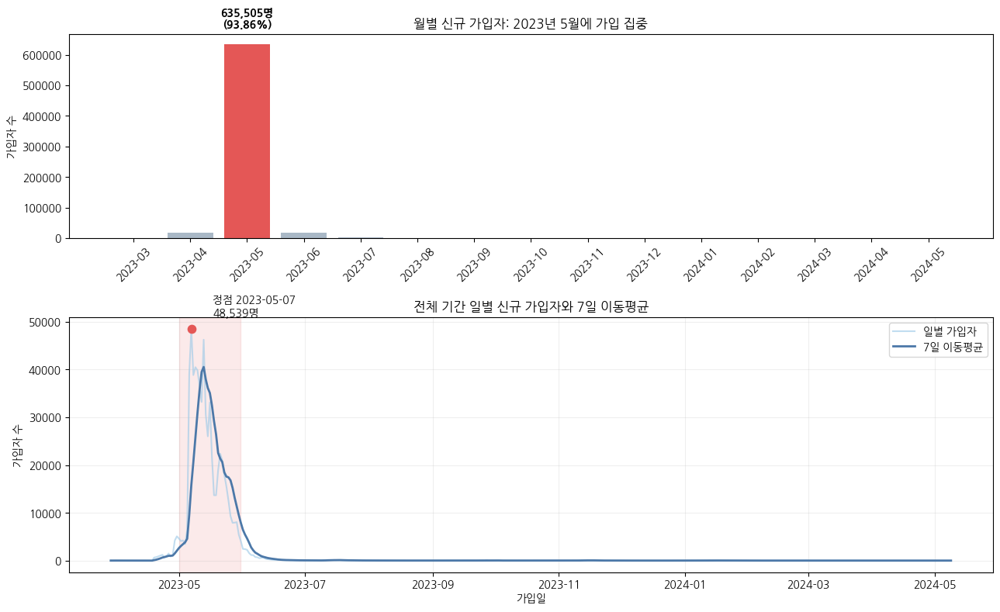

In [ ]:
# 월별·일별 가입 추이·7일 이동평균
daily = users.groupby("signup_date").size().rename("가입자 수").sort_index()
monthly = users.groupby("signup_month").size().rename("가입자 수").sort_index()

calendar = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily_calendar = daily.reindex(calendar, fill_value=0)
daily_7d = daily_calendar.rolling(window=7, min_periods=1).mean()

monthly_summary = monthly.to_frame()
monthly_summary["전월 대비 증가율"] = monthly_summary["가입자 수"].pct_change()
display(monthly_summary.style.format({"가입자 수": "{:,.0f}", "전월 대비 증가율": "{:.2%}"}, na_rep="-"))

april_count = int(monthly.get(pd.Period("2023-04"), 0))
may_count = int(monthly.loc[pd.Period("2023-05")])
may_share = may_count / len(users)
peak_date = daily.idxmax()
peak_count = int(daily.max())

summary_5m = pd.Series({
    "전체 사용자": f"{len(users):,}명",
    "2023년 4월 가입": f"{april_count:,}명",
    "2023년 5월 가입": f"{may_count:,}명",
    "5월/4월 가입자 배수": f"{may_count/april_count:.2f}배" if april_count else "계산 불가",
    "5월 비중": f"{may_share:.2%}",
    "일 최대 가입일": peak_date.date(),
    "일 최대 가입자": f"{peak_count:,}명",
})
display(summary_5m.to_frame("결과"))

fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={"height_ratios": [1, 1.25]})

labels = [str(x) for x in monthly.index]
bar_colors = ["#E45756" if x == pd.Period("2023-05") else "#A9B8C6" for x in monthly.index]
axes[0].bar(labels, monthly.values, color=bar_colors)
axes[0].set_title("월별 신규 가입자: 2023년 5월에 가입 집중")
axes[0].set_ylabel("가입자 수")
axes[0].tick_params(axis="x", rotation=45)
axes[0].annotate(
    f"{may_count:,}명\n({may_share:.2%})",
    xy=(labels.index("2023-05"), may_count), xytext=(0, 15),
    textcoords="offset points", ha="center", fontweight="bold",
)

axes[1].plot(daily_calendar.index, daily_calendar.values, color="#A0CBE8", alpha=.65, label="일별 가입자")
axes[1].plot(daily_7d.index, daily_7d.values, color="#4C78A8", linewidth=2, label="7일 이동평균")
axes[1].axvspan(pd.Timestamp("2023-05-01"), pd.Timestamp("2023-05-31"), color="#E45756", alpha=.12)
axes[1].scatter([peak_date], [peak_count], color="#E45756", s=55, zorder=3)
axes[1].annotate(
    f"정점 {peak_date.date()}\n{peak_count:,}명",
    (peak_date, peak_count), xytext=(20, 12), textcoords="offset points",
)
axes[1].set_title("전체 기간 일별 신규 가입자와 7일 이동평균")
axes[1].set_ylabel("가입자 수")
axes[1].set_xlabel("가입일")
axes[1].legend()
axes[1].grid(alpha=.2)

plt.tight_layout()
plt.show()

plt.close('all')


- 2023년 5월에 635,505명이 가입했다. 전체의 93.86%이며, 4월 19,060명의 약 33.34배다.
- 일별 정점은 5월 7일 48,539명이다. 유입 대부분이 5월의 짧은 기간에 몰렸다.


,구간,가입자,전체 비중
0,상위 1일,"48,539",7.17%
1,상위 3일,"135,292",19.98%
2,상위 7일,"289,603",42.77%
3,상위 14일,"477,575",70.53%
4,상위 30일,"633,181",93.52%


,결과
정점의 50% 아래로 내려간 시점,정점 후 10일
정점의 10% 아래로 내려간 시점,정점 후 24일
5/14~6/15 추정 반감기,4.22일
로그-선형 감쇠 적합도 R²,0.957


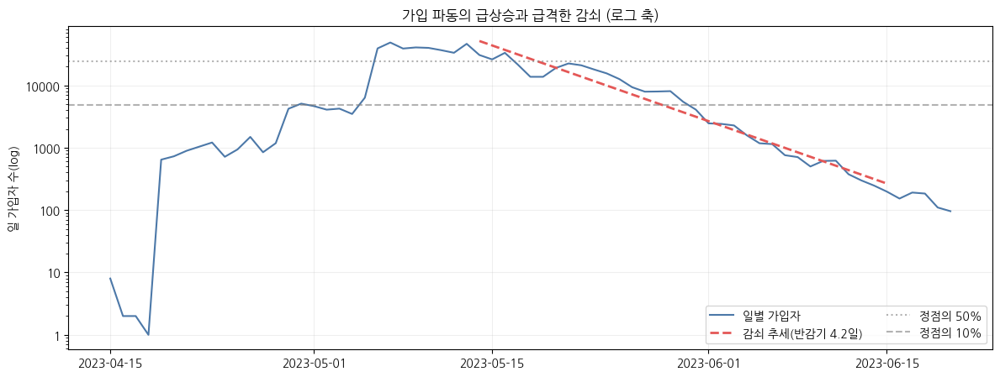

In [ ]:
# 상위 일자 가입 집중도·정점 이후 감소
sorted_daily = daily.sort_values(ascending=False)
concentration = []
for k in [1, 3, 7, 14, 30]:
    n = int(sorted_daily.head(k).sum())
    concentration.append([f"상위 {k}일", n, n / daily.sum()])
concentration = pd.DataFrame(concentration, columns=["구간", "가입자", "전체 비중"])
concentration["가입자"] = concentration["가입자"].map(lambda x: f"{x:,}")
concentration["전체 비중"] = concentration["전체 비중"].map(lambda x: f"{x:.2%}")
display(concentration)

decay = daily.loc["2023-05-14":"2023-06-15"]
x = np.arange(len(decay))
slope, intercept = np.polyfit(x, np.log(decay.values), 1)
fitted = np.exp(intercept + slope * x)
ss_res = np.sum((np.log(decay.values) - (intercept + slope * x)) ** 2)
ss_tot = np.sum((np.log(decay.values) - np.log(decay.values).mean()) ** 2)
r2 = 1 - ss_res / ss_tot
half_life = np.log(2) / (-slope)

after_peak = daily.loc[peak_date:]
days_to_half = int(np.argmax(after_peak.values < peak_count * .5))
days_to_tenth = int(np.argmax(after_peak.values < peak_count * .1))

display(pd.Series({
    "정점의 50% 아래로 내려간 시점": f"정점 후 {days_to_half}일",
    "정점의 10% 아래로 내려간 시점": f"정점 후 {days_to_tenth}일",
    "5/14~6/15 추정 반감기": f"{half_life:.2f}일",
    "로그-선형 감쇠 적합도 R²": f"{r2:.3f}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.plot(daily.loc["2023-04-15":"2023-06-20"], color="#4C78A8", label="일별 가입자")
ax.plot(decay.index, fitted, "--", color="#E45756", linewidth=2,
        label=f"감쇠 추세(반감기 {half_life:.1f}일)")
ax.axhline(peak_count * .5, color="gray", linestyle=":", alpha=.6, label="정점의 50%")
ax.axhline(peak_count * .1, color="gray", linestyle="--", alpha=.6, label="정점의 10%")
ax.set_yscale("log")
team7_plain_log_ticks(ax, 'y')
ax.set_title("가입 파동의 급상승과 급격한 감쇠 (로그 축)")
ax.set_ylabel("일 가입자 수(log)")
ax.legend(ncol=2)
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

plt.close('all')


- 가입 상위 7일에 전체의 42.77%, 상위 14일에 70.53%가 모였다. 정점에서 절반 아래로 줄기까지 10일, 10% 아래로 줄기까지 24일이 걸렸다.
- 5월 14일~6월 15일 감소 곡선의 추정 반감기는 4.22일이다. 급격히 유입된 만큼 감소도 빨랐다.


### 3-0-3. 가입 급증이 적재 오류인지 확인

- 동일한 생성 시각의 반복과 사용자 ID·생성 시각의 순서를 살펴본다.
- 단순 일괄 입력 여부를 점검하는 방법이며 모든 적재 오류를 검증하는 것은 아니다.


In [ ]:
# 가입 시각 중복·ID 순서 점검
may_users = users.loc[users["signup_month"] == pd.Period("2023-05")].copy()
same_timestamp = may_users.groupby("user_created_at").size()

ts_numeric = users["user_created_at"].astype("int64")
valid_id = users["user_id"].notna()
id_time_rho = spearmanr(users.loc[valid_id, "user_id"].astype("int64"), ts_numeric[valid_id]).statistic

batch_qa = pd.Series({
    "5월 행 수": f"{len(may_users):,}",
    "5월 고유 생성시각 수": f"{may_users['user_created_at'].nunique():,}",
    "고유 생성시각 비율": f"{may_users['user_created_at'].nunique()/len(may_users):.5%}",
    "완전히 같은 시각의 최대 계정 수": int(same_timestamp.max()),
    "user_id와 생성시각 순위상관": f"{id_time_rho:.6f}",
})
display(batch_qa.to_frame("결과"))

display(same_timestamp.sort_values(ascending=False).head(10).to_frame("같은 시각 계정 수"))


,결과
5월 행 수,"635,505"
5월 고유 생성시각 수,"635,502"
고유 생성시각 비율,99.99953%
완전히 같은 시각의 최대 계정 수,2
user_id와 생성시각 순위상관,0.999920


,같은 시각 계정 수
user_created_at,
2023-05-21 17:07:37.124684,2
2023-05-17 06:27:23.927580,2
2023-05-12 04:20:25.151806,2
2023-05-16 12:51:38.376967,1
2023-05-16 12:51:39.134423,1
2023-05-16 12:51:39.567006,1
2023-05-16 12:51:40.083503,1
2023-05-16 12:51:40.316154,1
2023-05-16 12:51:40.680047,1


- 5월 가입 635,505건의 고유 생성 시각은 635,502개로, 같은 시각의 계정은 최대 2개다.
- 사용자 ID와 생성 시각의 순위상관은 0.999920이다. 가입 기록은 대부분 서로 다른 시각에 순서대로 쌓였다.


### 3-0-4. 학교 첫 가입 이후의 확산

- 여기서 D0는 학교의 첫 가입일이다. 새 학교 진입과 학교 안의 추가 가입을 나눠 본다.
- 인원 도달일은 가입 기록으로 계산하며 실제 기능 활성화 시각은 별도다.


In [ ]:
# 학교 첫 가입일·상대일·인원 도달일
school_users = users.dropna(subset=["school_id"]).copy()
school_users["school_id"] = pd.to_numeric(school_users["school_id"], errors="coerce").astype("Int64")
school_users = school_users.dropna(subset=["school_id"]).sort_values(["school_id", "user_created_at", "user_id"])

first_signup = school_users.groupby("school_id")["signup_date"].min().rename("first_signup_date")
school_users = school_users.join(first_signup, on="school_id")
school_users["day_from_first"] = (school_users["signup_date"] - school_users["first_signup_date"]).dt.days
school_users["school_rank"] = school_users.groupby("school_id").cumcount() + 1

school_size = school_users.groupby("school_id").size().rename("final_accounts")
school = pd.DataFrame(index=school_size.index).join([school_size, first_signup])

for d in [0, 1, 3, 7, 14, 30]:
    col = school_users.loc[school_users["day_from_first"] <= d].groupby("school_id").size()
    school[f"cum_d{d}"] = col.reindex(school.index, fill_value=0)

for threshold in [10, 20, 40, 100]:
    hit = school_users.loc[school_users["school_rank"] == threshold].set_index("school_id")["signup_date"]
    school[f"date_{threshold}"] = hit.reindex(school.index)
    school[f"days_to_{threshold}"] = (school[f"date_{threshold}"] - school["first_signup_date"]).dt.days

print(f"학교 수: {len(school):,}")
display(school.head())


학교 수: 5,551


,final_accounts,first_signup_date,cum_d0,cum_d1,cum_d3,cum_d7,cum_d14,cum_d30,date_10,days_to_10,date_20,days_to_20,date_40,days_to_40,date_100,days_to_100
school_id,,,,,,,,,,,,,,,,
1,93,2023-03-29,10,10,10,14,15,38,2023-03-29,0.0,2023-04-17,19.0,2023-04-29,31.0,NaT,NaN
4,235,2023-05-08,1,1,15,203,231,233,2023-05-11,3.0,2023-05-12,4.0,2023-05-12,4.0,2023-05-13,5.0
5,160,2023-05-07,11,12,15,117,158,159,2023-05-07,0.0,2023-05-13,6.0,2023-05-13,6.0,2023-05-14,7.0
6,197,2023-05-01,1,1,2,5,168,194,2023-05-11,10.0,2023-05-11,10.0,2023-05-12,11.0,2023-05-13,12.0
7,114,2023-04-23,1,1,1,2,5,106,2023-05-13,20.0,2023-05-13,20.0,2023-05-13,20.0,2023-05-18,25.0


- 현재 학교를 기준으로 5,551개 학교의 첫 가입일과 10·20·40·100명 도달일을 만들었다.


,결과
5월에 처음 등장한 학교,"4,186개"
전체 학교 중 비중,75.41%
5월 가입 중 학교 D4~D30 가입,80.08%


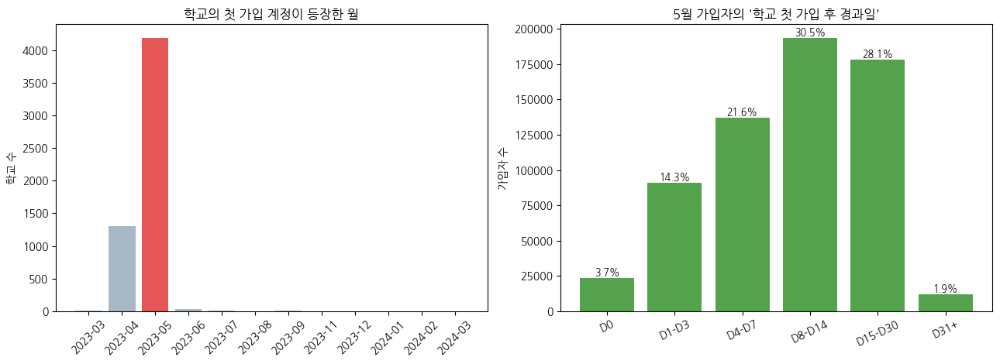

In [ ]:
# 신규 학교 진입·학교 내 추가 가입
school_first_month = school["first_signup_date"].dt.to_period("M").value_counts().sort_index()
may_first_schools = int(school_first_month.loc[pd.Period("2023-05")])

may_school_users = school_users.loc[school_users["signup_date"].dt.to_period("M") == pd.Period("2023-05")].copy()
age_band = pd.cut(
    may_school_users["day_from_first"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=["D0", "D1-D3", "D4-D7", "D8-D14", "D15-D30", "D31+"],
)
age_counts = age_band.value_counts(sort=False)

display(pd.Series({
    "5월에 처음 등장한 학교": f"{may_first_schools:,}개",
    "전체 학교 중 비중": f"{may_first_schools/len(school):.2%}",
    "5월 가입 중 학교 D4~D30 가입": f"{age_counts.loc[['D4-D7','D8-D14','D15-D30']].sum()/len(may_school_users):.2%}",
}).to_frame("결과"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar([str(x) for x in school_first_month.index], school_first_month.values,
            color=["#E45756" if x == pd.Period("2023-05") else "#A9B8C6" for x in school_first_month.index])
axes[0].set_title("학교의 첫 가입 계정이 등장한 월")
axes[0].set_ylabel("학교 수")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(age_counts.index.astype(str), age_counts.values, color="#54A24B")
axes[1].set_title("5월 가입자의 '학교 첫 가입 후 경과일'")
axes[1].set_ylabel("가입자 수")
axes[1].tick_params(axis="x", rotation=25)
for i, v in enumerate(age_counts.values):
    axes[1].text(i, v, f"{v/len(may_school_users):.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

plt.close('all')


- 4,186개 학교, 전체의 75.41%에서 첫 가입이 2023년 5월에 발생했다.
- 5월 가입자의 80.08%는 학교 첫 가입 후 D4~D30에 들어왔다. 새 학교가 늘어나는 동안 학교 안에서도 추가 가입이 이어졌다.


,median,p25,p75,p90,mean
day_from_first,,,,,
0,1.0,1.0,2.0,8.0,4.8
1,2.0,1.0,6.0,26.0,10.3
3,3.0,1.0,17.0,75.0,22.1
7,12.0,3.0,70.0,153.0,47.9
14,48.0,9.0,141.0,217.0,83.6
30,103.0,22.0,185.0,259.0,117.4


,결과
최종 40명 도달 학교,"3,897개 (70.20%)"
40명 도달 학교의 중앙 소요일,8일
도달 학교 중 D7 이내,46.96%
도달 학교 중 D14 이내,75.11%
도달 학교 중 D30 이내,97.74%


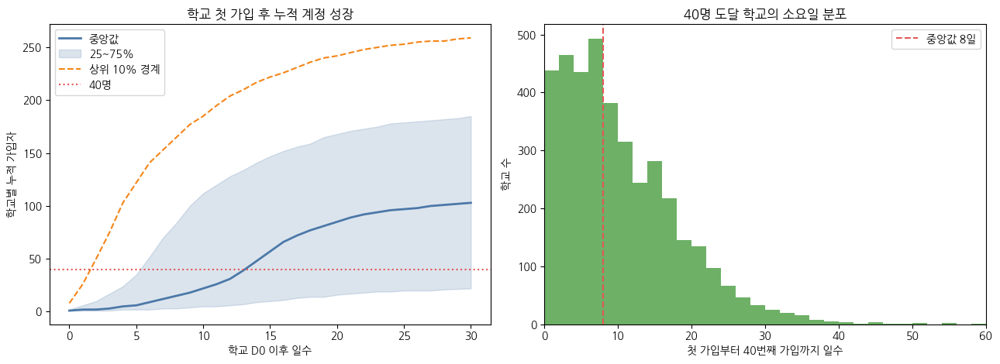

In [ ]:
# 학교 첫 가입 이후 누적 성장·40명 도달
school_day = school_users.groupby(["school_id", "day_from_first"]).size().rename("signups").reset_index()
grid = pd.MultiIndex.from_product([school.index, range(31)], names=["school_id", "day_from_first"]).to_frame(index=False)
aligned = grid.merge(school_day, how="left", on=["school_id", "day_from_first"]).fillna({"signups": 0})
aligned["cum_signups"] = aligned.groupby("school_id")["signups"].cumsum()
aligned_summary = aligned.groupby("day_from_first")["cum_signups"].agg(
    median="median",
    p25=lambda s: s.quantile(.25),
    p75=lambda s: s.quantile(.75),
    p90=lambda s: s.quantile(.90),
    mean="mean",
)

display(aligned_summary.loc[[0, 1, 3, 7, 14, 30]].round(1))

reached40 = school["days_to_40"].notna()
threshold_summary = pd.Series({
    "최종 40명 도달 학교": f"{reached40.sum():,}개 ({reached40.mean():.2%})",
    "40명 도달 학교의 중앙 소요일": f"{school.loc[reached40, 'days_to_40'].median():.0f}일",
    "도달 학교 중 D7 이내": f"{school.loc[reached40, 'days_to_40'].le(7).mean():.2%}",
    "도달 학교 중 D14 이내": f"{school.loc[reached40, 'days_to_40'].le(14).mean():.2%}",
    "도달 학교 중 D30 이내": f"{school.loc[reached40, 'days_to_40'].le(30).mean():.2%}",
})
display(threshold_summary.to_frame("결과"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
x = aligned_summary.index.to_numpy(dtype=float)
axes[0].plot(x, aligned_summary["median"].to_numpy(dtype=float), label="중앙값", color="#4C78A8", linewidth=2)
axes[0].fill_between(x,
                     aligned_summary["p25"].to_numpy(dtype=float),
                     aligned_summary["p75"].to_numpy(dtype=float),
                     alpha=.2, color="#4C78A8", label="25~75%")
axes[0].plot(x, aligned_summary["p90"].to_numpy(dtype=float), "--", color="#F58518", label="상위 10% 경계")
axes[0].axhline(40, color="#E45756", linestyle=":", label="40명")
axes[0].set_title("학교 첫 가입 후 누적 계정 성장")
axes[0].set_xlabel("학교 D0 이후 일수")
axes[0].set_ylabel("학교별 누적 가입자")
axes[0].legend()

axes[1].hist(school.loc[reached40, "days_to_40"], bins=np.arange(0, 61, 2), color="#54A24B", alpha=.85)
axes[1].axvline(school.loc[reached40, "days_to_40"].median(), color="#E45756", linestyle="--",
                label=f"중앙값 {school.loc[reached40, 'days_to_40'].median():.0f}일")
axes[1].set_xlim(0, 60)
axes[1].set_title("40명 도달 학교의 소요일 분포")
axes[1].set_xlabel("첫 가입부터 40번째 가입까지 일수")
axes[1].set_ylabel("학교 수")
axes[1].legend()

plt.tight_layout()
plt.show()

plt.close('all')


- 학교별 누적 가입자 중앙값은 D7 12명, D14 48명, D30 103명이다.
- 40명에 도달한 3,897개 학교의 중앙 소요일은 8일이며, 이 중 75.11%는 14일 안에 도달했다.


### 3-0-5. 학교 내부 가입 집중도

- 전국 일별 유입 분포를 기준으로 학교 내부의 가입 집중도를 계산한다.
- 학교별 연속 가입 간격으로 확산 속도의 차이도 살펴본다.


,결과
비교 학교(최종 40명 이상),"3,897개"
관측/기대 집중도 중앙값,3.08배
기대보다 더 집중된 학교 비율,99.46%
단측 Wilcoxon p-value,< 1e-300


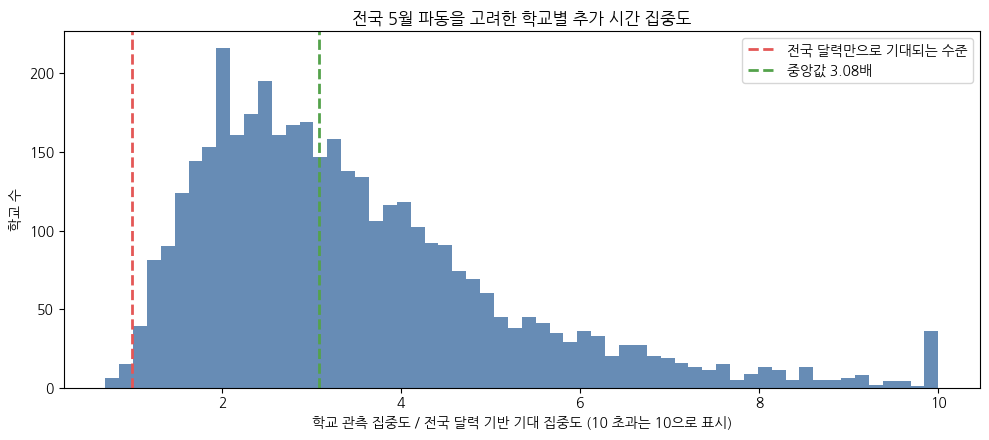

In [ ]:
# 전국 가입 분포 대비 학교별 집중도
global_day_prob = daily / daily.sum()
global_hhi = float((global_day_prob ** 2).sum())

school_calendar_day = school_users.groupby(["school_id", "signup_date"]).size().rename("n").reset_index()
school_calendar_day = school_calendar_day.join(school_size, on="school_id")
school_calendar_day["share_sq"] = (school_calendar_day["n"] / school_calendar_day["final_accounts"]) ** 2
observed_hhi = school_calendar_day.groupby("school_id")["share_sq"].sum()

school["observed_hhi"] = observed_hhi.reindex(school.index)

school["expected_hhi"] = global_hhi + (1 - global_hhi) / school["final_accounts"]
school["hhi_ratio"] = school["observed_hhi"] / school["expected_hhi"]
school["hhi_excess"] = school["observed_hhi"] - school["expected_hhi"]

hhi_sample = school.loc[school["final_accounts"] >= 40].copy()
hhi_test = wilcoxon(hhi_sample["hhi_excess"], alternative="greater")

display(pd.Series({
    "비교 학교(최종 40명 이상)": f"{len(hhi_sample):,}개",
    "관측/기대 집중도 중앙값": f"{hhi_sample['hhi_ratio'].median():.2f}배",
    "기대보다 더 집중된 학교 비율": f"{(hhi_sample['hhi_ratio'] > 1).mean():.2%}",
    "단측 Wilcoxon p-value": "< 1e-300" if hhi_test.pvalue == 0 else f"{hhi_test.pvalue:.2e}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(hhi_sample["hhi_ratio"].clip(upper=10), bins=60, color="#4C78A8", alpha=.85)
ax.axvline(1, color="#E45756", linestyle="--", linewidth=2, label="전국 달력만으로 기대되는 수준")
ax.axvline(hhi_sample["hhi_ratio"].median(), color="#54A24B", linestyle="--", linewidth=2,
           label=f"중앙값 {hhi_sample['hhi_ratio'].median():.2f}배")
ax.set_title("전국 5월 파동을 고려한 학교별 추가 시간 집중도")
ax.set_xlabel("학교 관측 집중도 / 전국 달력 기반 기대 집중도 (10 초과는 10으로 표시)")
ax.set_ylabel("학교 수")
ax.legend()
plt.tight_layout()
plt.show()

plt.close('all')


- 40명 이상 학교의 가입 집중도는 전국 분포에 따른 기대값보다 중앙 3.08배 높았다. 3,897개 학교 중 99.46%가 기대값을 넘었다.
- 전국적으로 5월에 유입이 몰린 점을 고려해도 학교 안에서는 가입이 더 짧은 시기에 집중됐다.


,결과
학교 수,"3,807개"
학교별 중앙 가입간격의 중앙값,21.2분
25% 지점,11.5분
75% 지점,59.6분
90% 지점,7.8시간


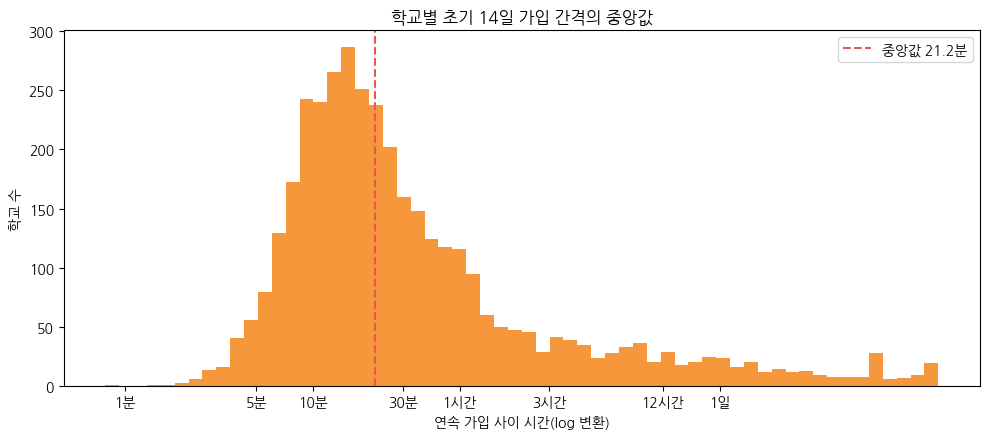

In [ ]:
# 학교 초기 14일 연속 가입 간격
early14 = school_users.loc[school_users["day_from_first"] <= 14].copy()
early14["prev_signup_at"] = early14.groupby("school_id")["user_created_at"].shift()
early14["gap_minutes"] = (early14["user_created_at"] - early14["prev_signup_at"]).dt.total_seconds() / 60
school_gap = early14.groupby("school_id")["gap_minutes"].median()
gap40 = school_gap.reindex(hhi_sample.index).dropna()

display(pd.Series({
    "학교 수": f"{len(gap40):,}개",
    "학교별 중앙 가입간격의 중앙값": f"{gap40.median():.1f}분",
    "25% 지점": f"{gap40.quantile(.25):.1f}분",
    "75% 지점": f"{gap40.quantile(.75):.1f}분",
    "90% 지점": f"{gap40.quantile(.90)/60:.1f}시간",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(np.log10(gap40.clip(lower=.01)), bins=60, color="#F58518", alpha=.85)
ticks = np.log10([1, 5, 10, 30, 60, 180, 720, 1440])
ax.set_xticks(ticks, ["1분", "5분", "10분", "30분", "1시간", "3시간", "12시간", "1일"])
ax.axvline(np.log10(gap40.median()), color="#E45756", linestyle="--",
           label=f"중앙값 {gap40.median():.1f}분")
ax.set_title("학교별 초기 14일 가입 간격의 중앙값")
ax.set_xlabel("연속 가입 사이 시간(log 변환)")
ax.set_ylabel("학교 수")
ax.legend()
plt.tight_layout()
plt.show()

plt.close('all')


- 간격을 계산한 3,807개 학교에서 학교별 중앙 가입 간격의 중앙값은 21.2분이다.
- 25% 지점은 11.5분, 75% 지점은 59.6분으로 학교마다 속도 차이가 있었다.


### 3-0-6. 초기 가입과 이후 성장

- 학교 첫 가입일(D0)부터 D3까지 네 날짜의 가입 규모와 D4~D14 추가 가입을 연결해 본다.
- D0~D3 정보로 D14까지의 40명 도달 여부를 예측한다. 가입을 늘리는 개입의 효과는 이 모델로 알 수 없다.


,결과
학교 수,"5,551"
D3 누적과 D4~D14 추가 가입의 Spearman ρ,0.349
p-value,5.48e-159


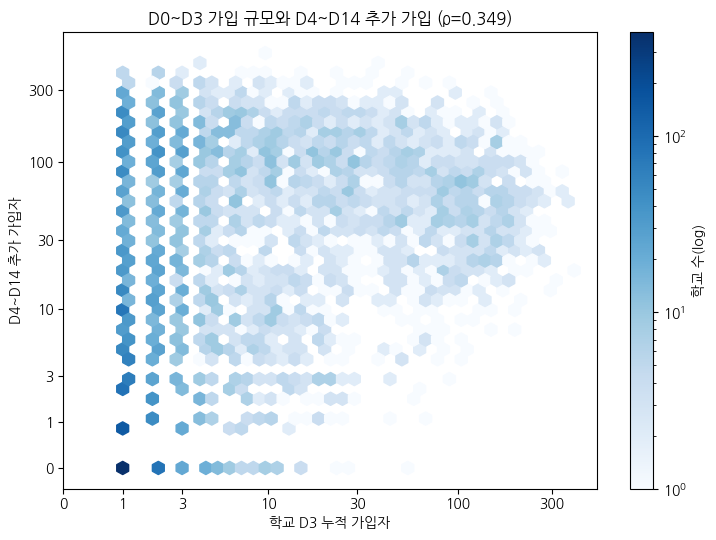

In [ ]:
# D0~D3 가입과 이후 추가 가입 관계
school["later_d4_d14"] = school["cum_d14"] - school["cum_d3"]
eligible_corr = school.loc[school["first_signup_date"] <= users["signup_date"].max() - pd.Timedelta(days=14)].copy()
momentum_rho, momentum_p = spearmanr(eligible_corr["cum_d3"], eligible_corr["later_d4_d14"])

display(pd.Series({
    "학교 수": f"{len(eligible_corr):,}",
    "D3 누적과 D4~D14 추가 가입의 Spearman ρ": f"{momentum_rho:.3f}",
    "p-value": f"{momentum_p:.2e}",
}).to_frame("결과"))

fig, ax = plt.subplots(figsize=(7.5, 5.5))
x_plot = np.log1p(eligible_corr["cum_d3"])
y_plot = np.log1p(eligible_corr["later_d4_d14"])
hb = ax.hexbin(x_plot, y_plot, gridsize=38, bins="log", mincnt=1, cmap="Blues")
raw_ticks = np.array([0, 1, 3, 10, 30, 100, 300])
ax.set_xticks(np.log1p(raw_ticks), raw_ticks)
ax.set_yticks(np.log1p(raw_ticks), raw_ticks)
ax.set_xlabel("학교 D3 누적 가입자")
ax.set_ylabel("D4~D14 추가 가입자")
ax.set_title(f"D0~D3 가입 규모와 D4~D14 추가 가입 (ρ={momentum_rho:.3f})")
fig.colorbar(hb, ax=ax, label="학교 수(log)")
plt.tight_layout()
plt.show()

plt.close('all')


- D3 누적 가입과 D4~D14 추가 가입의 순위상관은 0.349다. 초반 가입이 많은 학교에서 이후 가입도 많은 경향이 있지만 연관성은 강하지 않다.


In [ ]:
# 첫 가입일(D0)~D3의 네 날짜 정보로 D14까지 40명 도달 구분
daily_wide = school_day.pivot(index="school_id", columns="day_from_first", values="signups").fillna(0)
model_df = pd.DataFrame(index=school.index)
model_df["first_signup_date"] = school["first_signup_date"]
model_df["d0"] = daily_wide.get(0, pd.Series(0, index=daily_wide.index)).reindex(model_df.index, fill_value=0)
model_df["d1"] = daily_wide.get(1, pd.Series(0, index=daily_wide.index)).reindex(model_df.index, fill_value=0)
model_df["d2_d3"] = daily_wide.reindex(columns=[2, 3], fill_value=0).sum(axis=1).reindex(model_df.index, fill_value=0)
model_df["cum_d3"] = school["cum_d3"]
model_df["target_d14_40"] = school["days_to_40"].le(14).astype(int)

model_df = model_df.loc[
    model_df["first_signup_date"].dt.to_period("M").eq(pd.Period("2023-05"))
    & model_df["cum_d3"].lt(40)
].copy()

X = np.log1p(model_df[["d0", "d1", "d2_d3"]])
y = model_df["target_d14_40"]
cv = StratifiedKFold(5, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced"))
pred = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

auc = roc_auc_score(y, pred)
ap = average_precision_score(y, pred)
cut = np.quantile(pred, .80)
top20_rate = y[pred >= cut].mean()
lift = top20_rate / y.mean()

display(pd.Series({
    "모델 대상 학교": f"{len(y):,}개",
    "실제 D14 40명 도달률": f"{y.mean():.2%}",
    "5-fold ROC-AUC": f"{auc:.3f}",
    "Average Precision": f"{ap:.3f}",
    "예측 상위 20% 실제 도달률": f"{top20_rate:.2%}",
    "전체 대비 lift": f"{lift:.2f}배",
}).to_frame("결과"))

model.fit(X, y)
coef = pd.Series(model[-1].coef_[0], index=["D0 가입", "D1 가입", "D2~D3 가입"], name="표준화 계수")
display(coef.sort_values(ascending=False).to_frame())


,결과
모델 대상 학교,"3,325개"
실제 D14 40명 도달률,42.50%
5-fold ROC-AUC,0.713
Average Precision,0.688
예측 상위 20% 실제 도달률,74.14%
전체 대비 lift,1.74배


,표준화 계수
D2~D3 가입,0.817046
D1 가입,0.130405
D0 가입,0.039324


- 5월에 처음 진입하고 D3에 40명 미만인 3,325개 학교의 교차검증 ROC-AUC는 0.713이다.
- 예측 상위 20%의 실제 도달률은 74.14%로, 전체 대상 학교의 42.50%보다 높았다. 초기 가입 정보로 도달 가능성이 높은 학교를 어느 정도 골라낼 수 있었다.


### 3-0-7. 40명 도달 전후와 친구 행동

- 여기서부터 기준일은 학교의 40번째 가입일이다. 가입과 친구 요청의 흐름을 함께 본다.
- D0는 가입자 수로 정해지고 친구 요청은 가입자 사이의 행동이다. 전후 차이나 요청 건수만으로 기능 효과·외부 초대 전환을 계산할 수 없다.


,mean,median
relative_day,,
-7,0.86,0.0
-3,2.33,1.0
-2,3.55,2.0
-1,8.69,6.0
0,37.63,30.0
1,27.30,17.0
2,20.13,14.0
3,13.86,9.0
7,4.22,2.0


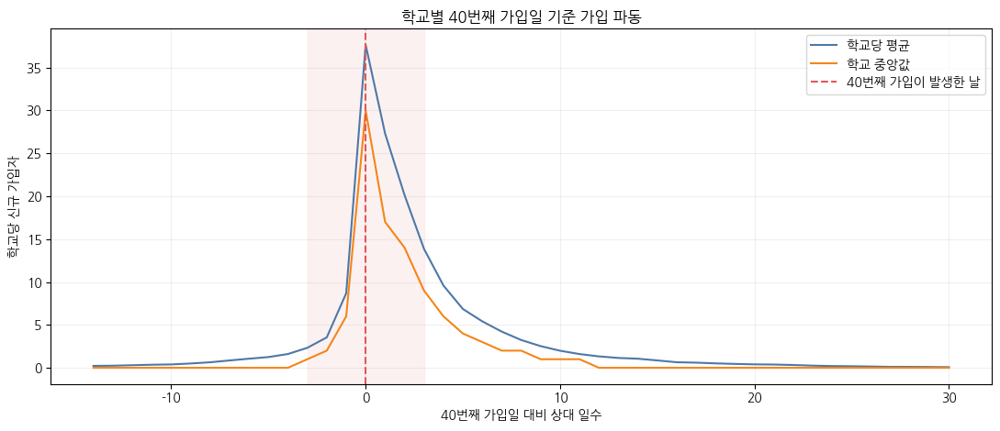

In [ ]:
# 40번째 가입일 전후 추가 가입 흐름
threshold_date = school.loc[school["date_40"].notna(), "date_40"].rename("threshold_date")
event = school_calendar_day.join(threshold_date, on="school_id")
event = event.dropna(subset=["threshold_date"])
event["relative_day"] = (event["signup_date"] - event["threshold_date"]).dt.days
event = event.loc[event["relative_day"].between(-14, 30)]

event_grid = pd.MultiIndex.from_product(
    [threshold_date.index, range(-14, 31)], names=["school_id", "relative_day"]
).to_frame(index=False)
event_full = event_grid.merge(event[["school_id", "relative_day", "n"]], how="left").fillna({"n": 0})
event_summary = event_full.groupby("relative_day")["n"].agg(mean="mean", median="median")

display(event_summary.loc[[-7, -3, -2, -1, 0, 1, 2, 3, 7, 14, 30]].round(2))

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(event_summary.index, event_summary["mean"], color="#4C78A8", label="학교당 평균")
ax.plot(event_summary.index, event_summary["median"], color="#F58518", label="학교 중앙값")
ax.axvline(0, color="#E45756", linestyle="--", label="40번째 가입이 발생한 날")
ax.axvspan(-3, 3, color="#E45756", alpha=.08)
ax.set_title("학교별 40번째 가입일 기준 가입 파동")
ax.set_xlabel("40번째 가입일 대비 상대 일수")
ax.set_ylabel("학교당 신규 가입자")
ax.legend()
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

plt.close('all')


- 학교당 평균 신규 가입자는 도달 전날 8.69명에서 D0 37.63명으로 늘고, D+1에는 27.30명으로 줄었다.
- D+14 가입자 중앙값은 0명이다. 도달 직후의 큰 유입이 오래 이어지지는 않았다.


,결과
친구 행동 총계,"17,147,175건"
5월 친구 행동 비중,93.25%
가입 당일 친구 행동 사용자,"605,582명 (89.44%)"
가입 당일 행동이 전체에서 차지하는 비중,63.75%
5월 일별 가입-친구행동 상관,ρ=0.965 (p=2.57e-18)


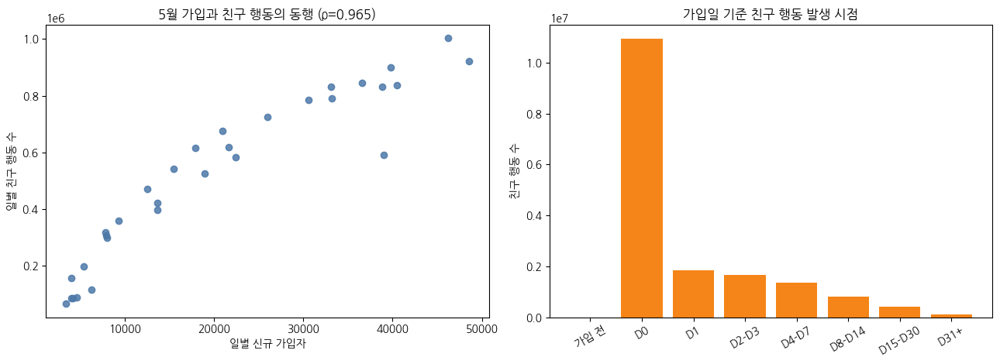

In [ ]:
# 가입 추이·친구요청·가입 당일 행동 비교
user_map = users[["user_id", "signup_date", "school_id"]].drop_duplicates("user_id")
positive_chunks = []

for chunk in pd.read_csv(
    ACTIVITY_PATH,
    usecols=["user_id", "activity_date", "friend_request_sent_count"],
    chunksize=500_000,
    low_memory=False,
):
    chunk = chunk.rename(columns={"friend_request_sent_count": "friend_action_count"})
    chunk["user_id"] = pd.to_numeric(chunk["user_id"], errors="coerce").astype("Int64")
    chunk["activity_date"] = pd.to_datetime(chunk["activity_date"], errors="coerce").dt.normalize()
    chunk["friend_action_count"] = pd.to_numeric(chunk["friend_action_count"], errors="coerce").fillna(0)
    chunk = chunk.loc[chunk["friend_action_count"] > 0]
    if not chunk.empty:
        positive_chunks.append(chunk)

friend = pd.concat(positive_chunks, ignore_index=True)
friend = friend.merge(user_map, on="user_id", how="left", validate="many_to_one")
friend["days_since_signup"] = (friend["activity_date"] - friend["signup_date"]).dt.days

daily_friend = friend.groupby("activity_date")["friend_action_count"].sum().rename("친구 행동")
daily_compare = pd.concat([daily.rename("가입"), daily_friend], axis=1).fillna(0)
may_daily = daily_compare.loc["2023-05-01":"2023-05-31"]
friend_rho_may, friend_p_may = spearmanr(may_daily["가입"], may_daily["친구 행동"])

d0_friend = friend.loc[friend["days_since_signup"] == 0]
d0_users = d0_friend["user_id"].nunique()
d0_actions = d0_friend["friend_action_count"].sum()
may_actions = friend.loc[friend["activity_date"].dt.to_period("M") == pd.Period("2023-05"), "friend_action_count"].sum()

display(pd.Series({
    "친구 행동 총계": f"{friend['friend_action_count'].sum():,.0f}건",
    "5월 친구 행동 비중": f"{may_actions/friend['friend_action_count'].sum():.2%}",
    "가입 당일 친구 행동 사용자": f"{d0_users:,}명 ({d0_users/len(users):.2%})",
    "가입 당일 행동이 전체에서 차지하는 비중": f"{d0_actions/friend['friend_action_count'].sum():.2%}",
    "5월 일별 가입-친구행동 상관": f"ρ={friend_rho_may:.3f} (p={friend_p_may:.2e})",
}).to_frame("결과"))

bands = pd.cut(
    friend["days_since_signup"],
    bins=[-np.inf, -1, 0, 1, 3, 7, 14, 30, np.inf],
    labels=["가입 전", "D0", "D1", "D2-D3", "D4-D7", "D8-D14", "D15-D30", "D31+"],
)
band_actions = friend.groupby(bands, observed=False)["friend_action_count"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(may_daily["가입"], may_daily["친구 행동"], color="#4C78A8", alpha=.85)
axes[0].set_xlabel("일별 신규 가입자")
axes[0].set_ylabel("일별 친구 행동 수")
axes[0].set_title(f"5월 가입과 친구 행동의 동행 (ρ={friend_rho_may:.3f})")

axes[1].bar(band_actions.index.astype(str), band_actions.values, color="#F58518")
axes[1].set_title("가입일 기준 친구 행동 발생 시점")
axes[1].set_ylabel("친구 행동 수")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

plt.close('all')


- 친구 요청 17,147,175건 중 93.25%가 5월에 발생했고, 전체의 63.75%는 사용자의 가입 당일에 발생했다.
- 5월 일별 가입자와 친구 요청의 순위상관은 0.965다. 가입과 첫 관계 연결이 같은 시기에 집중됐다.


### 3-0-8. 40명 도달 이후 친구 요청과 수락

- 40명 도달 이후 발송량과 최종 수락률을 구간별로 비교한다.
- 학교별 누적 가입자 1인당 발송 수(i)와 최종 수락률(c)의 곱을 구한 뒤 학교 간 평균을 낸다.
- In-App K는 가입자 사이의 수락 관계 지표이며, 외부 초대의 신규 가입 전환을 나타내는 K-Factor와는 다르다.


In [ ]:
# Viral 추가 분석 입력·청크 크기
vp48_root = Path(MART_DIR)
vp48_chunk_size = 200_000
vp48_files = {
    'school': vp48_root / 'mart_school_viral_daily_v2.csv.gz',
    'user': vp48_root / 'mart_user_acquisition_profile_v2.csv.gz',
    'request': vp48_root / 'mart_friend_request_event_v2.csv.gz',
}
for vp48_label, vp48_path in vp48_files.items():
    if not vp48_path.is_file():
        raise FileNotFoundError(f'Viral 추가 분석 파일 없음: {vp48_path}')
print('추가 분석 마트:', ', '.join(path.name for path in vp48_files.values()))


추가 분석 마트: mart_school_viral_daily_v2.csv.gz, mart_user_acquisition_profile_v2.csv.gz, mart_friend_request_event_v2.csv.gz


**계산 기준**

- 학교 일별 마트에서 40명 도달 표시가 있는 학교를 사용한다. D0는 현재 학교 정보를 바탕으로 계산한 40번째 가입일이며 실제 기능 개방일은 아니다.
- D0~D8은 9개 날짜이나 코드의 초기 가입·발송 일평균은 합계를 8로 나눈 값이다. 이후 구간은 기록된 패널 날짜 수로 나누므로 두 구간의 일평균은 동일한 분모 기준이 아니다.
- 요청이 없거나 이후 구간이 없는 학교의 해당 비율은 0으로 처리해 학교 평균에 포함한다.


In [ ]:
# 학교별·구간별 가입·발송·최종 수락 집계
vp48_school_cols = [
    'school_id', 'activity_date', 'current_roster_reached_40_flag',
    'days_from_40th_signup_current_roster', 'new_account_count_current_roster',
    'sent_request_created_count', 'sent_created_final_accepted_count',
    'cumulative_account_count_current_roster',
]
vp48_numeric_cols = vp48_school_cols[2:]
vp48_parts = []
vp48_valid_schools = set()
vp48_school_rows = 0
vp48_school_missing_day = 0
for vp48_chunk in pd.read_csv(
    vp48_files['school'], compression='gzip', usecols=vp48_school_cols,
    chunksize=vp48_chunk_size, na_values=[r'\N', 'NULL', ''],
):
    vp48_school_rows += len(vp48_chunk)
    vp48_school_missing_day += int(vp48_chunk['days_from_40th_signup_current_roster'].isna().sum())
    for vp48_col in vp48_numeric_cols:
        vp48_chunk[vp48_col] = pd.to_numeric(vp48_chunk[vp48_col], errors='coerce').fillna(0)
    vp48_reached = vp48_chunk.loc[vp48_chunk['current_roster_reached_40_flag'].eq(1)].copy()
    if vp48_reached.empty:
        continue
    vp48_valid_schools.update(vp48_reached['school_id'].unique())
    vp48_offset = vp48_reached['days_from_40th_signup_current_roster']
    vp48_reached['stage'] = np.select(
        [vp48_offset.between(0, 8), vp48_offset.gt(8)],
        ['golden_8d', 'after_8d'], default='other',
    )
    vp48_parts.append(vp48_reached.groupby(['school_id', 'stage']).agg(
        days=('activity_date', 'nunique'),
        new_users=('new_account_count_current_roster', 'sum'),
        requests=('sent_request_created_count', 'sum'),
        accepted=('sent_created_final_accepted_count', 'sum'),
        max_cum_users=('cumulative_account_count_current_roster', 'max'),
    ).reset_index())
    del vp48_reached, vp48_offset, vp48_chunk

if not vp48_parts:
    raise ValueError('학교 일별 마트에 40명 도달 학교가 없습니다.')
vp48_agg_k = pd.concat(vp48_parts, ignore_index=True).groupby(['school_id', 'stage']).agg(
    days=('days', 'sum'), new_users=('new_users', 'sum'),
    requests=('requests', 'sum'), accepted=('accepted', 'sum'),
    max_cum_users=('max_cum_users', 'max'),
).reset_index()
vp48_metric_names = ['days', 'new_users', 'requests', 'accepted', 'max_cum_users']
vp48_k_pivot = vp48_agg_k.pivot(index='school_id', columns='stage').reindex(
    columns=pd.MultiIndex.from_product([vp48_metric_names, ['golden_8d', 'after_8d', 'other']]),
).fillna(0)
vp48_valid_schools = sorted(vp48_valid_schools)
print(f'40명 도달 학교: {len(vp48_valid_schools):,}개교')
del vp48_parts
gc.collect();


40명 도달 학교: 3,896개교


In [ ]:
# 학교별 1인당 발송·수락률·In-App K
vp48_school_k_records = []
for vp48_sid in vp48_valid_schools:
    vp48_u_g = vp48_k_pivot.loc[vp48_sid, ('new_users', 'golden_8d')]
    vp48_inv_g = vp48_k_pivot.loc[vp48_sid, ('requests', 'golden_8d')]
    vp48_acc_g = vp48_k_pivot.loc[vp48_sid, ('accepted', 'golden_8d')]
    vp48_cum_u_g = max(vp48_k_pivot.loc[vp48_sid, ('max_cum_users', 'golden_8d')], 40)
    vp48_days_a = vp48_k_pivot.loc[vp48_sid, ('days', 'after_8d')]
    vp48_u_a = vp48_k_pivot.loc[vp48_sid, ('new_users', 'after_8d')]
    vp48_inv_a = vp48_k_pivot.loc[vp48_sid, ('requests', 'after_8d')]
    vp48_acc_a = vp48_k_pivot.loc[vp48_sid, ('accepted', 'after_8d')]
    vp48_cum_u_a = max(vp48_k_pivot.loc[vp48_sid, ('max_cum_users', 'after_8d')], vp48_cum_u_g)
    vp48_signup_rate_g = vp48_u_g / 8.0
    vp48_signup_rate_a = vp48_u_a / vp48_days_a if vp48_days_a > 0 else 0
    vp48_inv_rate_g = vp48_inv_g / 8.0
    vp48_inv_rate_a = vp48_inv_a / vp48_days_a if vp48_days_a > 0 else 0
    vp48_i_g = vp48_inv_g / vp48_cum_u_g if vp48_cum_u_g > 0 else 0
    vp48_i_a = vp48_inv_a / vp48_cum_u_a if vp48_cum_u_a > 0 else 0
    vp48_c_g = vp48_acc_g / vp48_inv_g if vp48_inv_g > 0 else 0
    vp48_c_a = vp48_acc_a / vp48_inv_a if vp48_inv_a > 0 else 0
    vp48_school_k_records.append({
        'school_id': vp48_sid,
        'signup_rate_g': vp48_signup_rate_g, 'signup_rate_a': vp48_signup_rate_a,
        'inv_rate_g': vp48_inv_rate_g, 'inv_rate_a': vp48_inv_rate_a,
        'i_g': vp48_i_g, 'i_a': vp48_i_a, 'c_g': vp48_c_g, 'c_a': vp48_c_a,
        'k_g': vp48_i_g * vp48_c_g, 'k_a': vp48_i_a * vp48_c_a,
    })
vp48_df_k_summary = pd.DataFrame(vp48_school_k_records)


In [ ]:
# 학교별 지표 평균·전후 차이
def vp48_change_text(before, after):
    if before == 0 or not np.isfinite(before) or not np.isfinite(after):
        return '계산 불가'
    change = (after - before) / before * 100
    ratio = after / before
    return f'{change:+.1f}% (이후/초기 {ratio:.3f}배)'

vp48_k_means = vp48_df_k_summary.drop(columns='school_id').mean()
vp48_k_summary_table = pd.DataFrame({
    '비교 지표': ['신규 가입자 수 (명/일)', '학교 발송량 (건/일)',
                '1인당 발송 수 (i, 건/인)', '요청 최종 수락률 (c)', 'In-App K (i × c)'],
    'D0~D8 (초기 일평균 분모: 8)': [
        f"{vp48_k_means['signup_rate_g']:.2f}", f"{vp48_k_means['inv_rate_g']:.1f}",
        f"{vp48_k_means['i_g']:.2f}", f"{vp48_k_means['c_g'] * 100:.1f}%",
        f"{vp48_k_means['k_g']:.2f}",
    ],
    'D8 이후': [
        f"{vp48_k_means['signup_rate_a']:.2f}", f"{vp48_k_means['inv_rate_a']:.1f}",
        f"{vp48_k_means['i_a']:.2f}", f"{vp48_k_means['c_a'] * 100:.1f}%",
        f"{vp48_k_means['k_a']:.2f}",
    ],
    '전후 차이': [
        vp48_change_text(vp48_k_means['signup_rate_g'], vp48_k_means['signup_rate_a']),
        vp48_change_text(vp48_k_means['inv_rate_g'], vp48_k_means['inv_rate_a']),
        vp48_change_text(vp48_k_means['i_g'], vp48_k_means['i_a']),
        f"{(vp48_k_means['c_a'] - vp48_k_means['c_g']) * 100:+.1f}%p",
        vp48_change_text(vp48_k_means['k_g'], vp48_k_means['k_a']),
    ],
})
display(vp48_k_summary_table)


,비교 지표,D0~D8 (원코드 기준),D8 이후,전후 차이
0,신규 가입자 수 (명/일),16.03,0.05,-99.7% (이후/초기 0.003배)
1,학교 발송량 (건/일),436.5,1.9,-99.6% (이후/초기 0.004배)
2,"1인당 발송 수 (i, 건/인)",21.19,3.76,-82.3% (이후/초기 0.177배)
3,요청 최종 수락률 (c),75.6%,50.4%,-25.1%p
4,In-App K (i × c),16.32,2.16,-86.7% (이후/초기 0.133배)


- 1인당 발송 수는 21.19건에서 3.76건으로, 최종 수락률은 75.6%에서 50.4%로 낮아졌다.
- 학교별 In-App K의 평균은 16.32에서 2.16로 낮아졌다. 학교마다 곱을 구한 뒤 평균을 내므로, 평균 i와 평균 c를 곱한 값과는 다르다.
- 초기 구간 뒤에는 발송과 수락이 모두 약해졌다. 다만 비교 기간의 길이와 이용자 구성이 달라, 40명 조건이나 친구 관계의 포화가 원인이라고 단정할 수는 없다.


### 3-0-9. 친구 요청의 최종 수락 상태와 갱신 간격

- 40명 도달 사용자 프로필을 발신자와 연결한다. 앞의 학교 일별 분석과 모집단이 다르다.
- 40번째 가입 시각(T40)부터 8일 뒤까지와 그 이후를 비교한다. 앞의 D0~D8 날짜 구간과 경계가 다르다.
- 요청 생성부터 마지막 갱신까지의 간격이며, 실제 수락 시각이나 신규 가입 전환 주기는 아니다.


In [ ]:
# 사용자별 40번째 가입 시각 연결
vp48_user_acq = pd.read_csv(
    vp48_files['user'], compression='gzip',
    usecols=['user_id', 'current_roster_40th_signup_at', 'current_roster_reached_40_flag'],
    na_values=[r'\N', 'NULL', ''],
)
vp48_user_acq = vp48_user_acq.loc[pd.to_numeric(
    vp48_user_acq['current_roster_reached_40_flag'], errors='coerce',
).eq(1)].copy()
vp48_user_acq['user_id'] = pd.to_numeric(vp48_user_acq['user_id'], errors='raise')
if vp48_user_acq['user_id'].duplicated().any():
    raise ValueError('40명 도달 사용자 프로필에 중복 user_id가 있습니다.')
vp48_user_acq['t40'] = pd.to_datetime(
    vp48_user_acq['current_roster_40th_signup_at'], format='mixed', errors='coerce',
)
vp48_invalid_t40 = int(vp48_user_acq['t40'].isna().sum())
vp48_user_t40 = vp48_user_acq.set_index('user_id')['t40']
vp48_timing_user_count = len(vp48_user_t40)
print(f'40명 도달 사용자 프로필: {vp48_timing_user_count:,}명 / 기준 시각 결측: {vp48_invalid_t40:,}명')
del vp48_user_acq
gc.collect();


40명 도달 사용자 프로필: 655,502명 / 기준 시각 결측: 0명


In [ ]:
# 최종 수락 요청·생성부터 마지막 갱신까지의 간격
vp48_golden_cycle_hours = []
vp48_after_cycle_hours = []
vp48_request_rows = 0
vp48_missing_interval = 0
vp48_missing_negative_flag = 0
vp48_invalid_request_at = 0
for vp48_chunk in pd.read_csv(
    vp48_files['request'], compression='gzip',
    usecols=['send_user_id', 'final_status_code', 'request_created_at_raw',
             'created_to_last_update_seconds', 'negative_update_interval_flag'],
    chunksize=vp48_chunk_size, na_values=[r'\N', 'NULL', ''],
):
    vp48_request_rows += len(vp48_chunk)
    vp48_chunk['created_to_last_update_seconds'] = pd.to_numeric(
        vp48_chunk['created_to_last_update_seconds'], errors='coerce',
    )
    vp48_chunk['negative_update_interval_flag'] = pd.to_numeric(
        vp48_chunk['negative_update_interval_flag'], errors='coerce',
    )
    vp48_final_a = vp48_chunk['final_status_code'].eq('A')
    vp48_missing_negative_flag += int((vp48_final_a & vp48_chunk['negative_update_interval_flag'].isna()).sum())
    vp48_missing_interval += int((vp48_final_a
        & vp48_chunk['negative_update_interval_flag'].fillna(0).eq(0)
        & vp48_chunk['created_to_last_update_seconds'].isna()).sum())
    vp48_chunk['created_to_last_update_seconds'] = vp48_chunk['created_to_last_update_seconds'].fillna(0)
    vp48_chunk['negative_update_interval_flag'] = vp48_chunk['negative_update_interval_flag'].fillna(0)
    vp48_acc = vp48_chunk.loc[
        vp48_final_a & vp48_chunk['negative_update_interval_flag'].eq(0)
    ].copy()
    if vp48_acc.empty:
        continue
    vp48_acc['hours'] = vp48_acc['created_to_last_update_seconds'] / 3600.0
    vp48_acc['req_at'] = pd.to_datetime(vp48_acc['request_created_at_raw'], format='mixed', errors='coerce')
    vp48_invalid_request_at += int(vp48_acc['req_at'].isna().sum())
    vp48_t40_series = pd.to_numeric(vp48_acc['send_user_id'], errors='coerce').map(vp48_user_t40)
    vp48_t40_8_series = vp48_t40_series + pd.Timedelta(days=8)
    vp48_cond_g = vp48_acc['req_at'].ge(vp48_t40_series) & vp48_acc['req_at'].le(vp48_t40_8_series)
    vp48_cond_a = vp48_acc['req_at'].gt(vp48_t40_8_series)
    vp48_golden_cycle_hours.append(vp48_acc.loc[vp48_cond_g, 'hours'].to_numpy(copy=True))
    vp48_after_cycle_hours.append(vp48_acc.loc[vp48_cond_a, 'hours'].to_numpy(copy=True))
    del vp48_chunk, vp48_acc, vp48_t40_series, vp48_t40_8_series, vp48_cond_g, vp48_cond_a, vp48_final_a

vp48_arr_golden_c = np.concatenate(vp48_golden_cycle_hours) if vp48_golden_cycle_hours else np.array([], dtype=float)
vp48_arr_after_c = np.concatenate(vp48_after_cycle_hours) if vp48_after_cycle_hours else np.array([], dtype=float)
del vp48_golden_cycle_hours, vp48_after_cycle_hours, vp48_user_t40
gc.collect();
vp48_data_checks = pd.DataFrame([
    ['학교 일별 마트 행 수', vp48_school_rows],
    ['학교 일별 마트의 40명 도달 학교 수', len(vp48_valid_schools)],
    ['사용자 프로필의 40명 도달 사용자 수', vp48_timing_user_count],
    ['친구 요청 마트 행 수', vp48_request_rows],
    ['초기 구간 최종 수락 요청 수', len(vp48_arr_golden_c)],
    ['이후 구간 최종 수락 요청 수', len(vp48_arr_after_c)],
    ['최종 수락 건 중 0으로 대체한 갱신 간격 결측', vp48_missing_interval],
    ['최종 수락 건 중 0으로 대체한 음수 여부 결측', vp48_missing_negative_flag],
    ['최종 수락 건 중 요청 시각 변환 실패', vp48_invalid_request_at],
    ['40명 도달 사용자 중 기준 시각 결측', vp48_invalid_t40],
], columns=['확인 항목', '건수'])
display(vp48_data_checks)


,확인 항목,건수
0,학교 일별 마트 행 수,2428008
1,학교 일별 마트의 40명 도달 학교 수,3896
2,사용자 프로필의 40명 도달 사용자 수,655502
3,친구 요청 마트 행 수,17147175
4,초기 구간 최종 수락 요청 수,10021266
5,이후 구간 최종 수락 요청 수,1767826
6,최종 수락 건 중 0으로 대체한 갱신 간격 결측,0
7,최종 수락 건 중 0으로 대체한 음수 여부 결측,0
8,최종 수락 건 중 요청 시각 변환 실패,0
9,40명 도달 사용자 중 기준 시각 결측,0


- 최종 상태가 수락(A)이고 갱신 간격이 음수로 표시되지 않은 요청을 사용했다.
- 최종 수락 요청에서 갱신 간격 결측·음수 여부 결측·요청 시각 변환 실패는 모두 0건이었다.


In [ ]:
# 구간별 평균·중앙값·24시간·3시간 이내 비율
def vp48_get_stats(arr):
    if len(arr) == 0:
        return (np.nan,) * 6
    mean_h = np.mean(arr)
    median_h = np.median(arr)
    p24 = np.mean(arr <= 24.0) * 100
    p3 = np.mean(arr <= 3.0) * 100
    return mean_h, mean_h / 24.0, median_h, median_h / 24.0, p24, p3

vp48_g_mean_h, vp48_g_mean_d, vp48_g_med_h, vp48_g_med_d, vp48_g_p24, vp48_g_p3 = vp48_get_stats(vp48_arr_golden_c)
vp48_a_mean_h, vp48_a_mean_d, vp48_a_med_h, vp48_a_med_d, vp48_a_p24, vp48_a_p3 = vp48_get_stats(vp48_arr_after_c)
vp48_cycle_stats = pd.DataFrame([
    ['T40~T40+8일', len(vp48_arr_golden_c), vp48_g_mean_h, vp48_g_med_h, vp48_g_p24, vp48_g_p3],
    ['T40+8일 이후', len(vp48_arr_after_c), vp48_a_mean_h, vp48_a_med_h, vp48_a_p24, vp48_a_p3],
], columns=['구간', '요청 수', '평균 시간', '중앙값 시간', '24시간 이내 %', '3시간 이내 %'])
del vp48_arr_golden_c, vp48_arr_after_c
gc.collect();


In [ ]:
# 친구 요청 갱신 간격 비교표
def vp48_hours_change(before, after):
    if not np.isfinite(before) or not np.isfinite(after) or before == 0:
        return '계산 불가'
    return f'{after - before:+.1f}시간 (이후/초기 {after / before:.2f}배)'

vp48_cycle_summary_table = pd.DataFrame({
    '구분': ['평균 간격', '중앙값', '24시간 이내 비율', '3시간 이내 비율'],
    'T40~T40+8일': [
        f'{vp48_g_mean_h:.1f}시간 ({vp48_g_mean_d:.2f}일)',
        f'{vp48_g_med_h:.1f}시간 ({vp48_g_med_d:.2f}일)',
        f'{vp48_g_p24:.1f}%', f'{vp48_g_p3:.1f}%',
    ],
    'T40+8일 이후': [
        f'{vp48_a_mean_h:.1f}시간 ({vp48_a_mean_d:.2f}일)',
        f'{vp48_a_med_h:.1f}시간 ({vp48_a_med_d:.2f}일)',
        f'{vp48_a_p24:.1f}%', f'{vp48_a_p3:.1f}%',
    ],
    '전후 차이': [
        vp48_hours_change(vp48_g_mean_h, vp48_a_mean_h),
        vp48_hours_change(vp48_g_med_h, vp48_a_med_h),
        f'{vp48_a_p24 - vp48_g_p24:+.1f}%p',
        f'{vp48_a_p3 - vp48_g_p3:+.1f}%p',
    ],
})
display(vp48_cycle_summary_table)


,구분,T40~T40+8일,T40+8일 이후,전후 차이
0,평균 간격,31.1시간 (1.30일),83.4시간 (3.47일),+52.2시간 (이후/초기 2.68배)
1,중앙값,4.1시간 (0.17일),17.0시간 (0.71일),+12.9시간 (이후/초기 4.12배)
2,24시간 이내 비율,79.0%,58.4%,-20.6%p
3,3시간 이내 비율,45.4%,25.0%,-20.4%p


- 갱신 간격의 중앙값은 4.1시간에서 17.0시간으로 늘었다. 24시간 이내 비율은 79.0%에서 58.4%로 낮아졌다.
- 이 비율의 분모는 각 구간에서 보낸 최종 수락 요청이다. 모든 요청의 수락률이나 학교별 비율의 평균과는 다르다.
- 나중에 보낸 요청은 수락 결과를 관측할 시간이 짧다. 미수락 요청도 빠져 있어, 이 차이를 전체 사용자의 수락 속도 변화로 그대로 해석하기는 어렵다.


In [ ]:
# 추가 분석 결과 보존·임시 변수 정리
vp48_keep = {
    'vp48_df_k_summary', 'vp48_k_summary_table', 'vp48_k_means',
    'vp48_cycle_summary_table', 'vp48_cycle_stats', 'vp48_data_checks',
    'vp48_change_text', 'vp48_get_stats', 'vp48_hours_change',
}
for vp48_name in list(globals()):
    if vp48_name.startswith('vp48_') and vp48_name not in vp48_keep and vp48_name not in {'vp48_keep', 'vp48_name'}:
        globals().pop(vp48_name, None)
del vp48_name, vp48_keep
gc.collect();


### 3-0-10. 학교 단위 확산으로 볼 수 있는 범위

- 유입 시기, 학교 내부 집중도, 초기 성장 결과를 묶어 정리한다.
- 개인 간 초대 기록이 없어 실제 전파 경로와 외부 초대 기반 K-Factor는 계산 범위에서 제외한다. 앞의 In-App K와는 구분한다.


In [ ]:
# Viral 분석 결과 정리
evidence = pd.DataFrame([
    ["시간적 폭발", "5월 635,505명·전체 93.86%, 상위 14일 70.53%", "매우 강함", "짧은 획득 파동"],
    ["빠른 감쇠", "정점 후 24일 만에 10% 미만, 추정 반감기 4.2일", "강함", "바이럴 앱의 급등락과 부합"],
    ["학교 범위 확장", "4,186개 학교가 5월에 처음 등장", "강함", "소수 학교만의 현상 아님"],
    ["학교 내부 확산", "40명 도달 학교 중앙 8일, 초기 가입간격 중앙 21.2분", "강함", "학교 안의 빠른 연쇄 패턴"],
    ["전국 파동 통제", "학교 집중도 중앙 3.08배, 99.46%가 기대 초과", "매우 강함", "전국 공통 노출만으로 설명 부족"],
    ["초기 모멘텀", "D3→D4~D14 ρ=0.349, 모델 AUC≈0.713", "보통", "초기 속도가 이후 성장과 연결"],
    ["단순 배치 반증", "5월 타임스탬프 99.99953% 고유, ID-시간 ρ≈0.99992", "보통~강함", "단순 동시 INSERT와 불일치"],
    ["친구 행동", "가입과 ρ≈0.965지만 63.75%가 D0", "보조", "초대가 아닌 온보딩 가능성"],
    ["외부 공개 자료", "5월 60만·자연 확산·앱스토어 1위라는 창업자 회고", "보조", "데이터 패턴과 방향 일치"],
], columns=["검증 축", "관측 결과", "증거 강도", "해석"])
display(evidence)

team7_release_unused('105', '3-0 완료')


,검증 축,관측 결과,증거 강도,해석
0,시간적 폭발,"5월 635,505명·전체 93.86%, 상위 14일 70.53%",매우 강함,짧은 획득 파동
1,빠른 감쇠,"정점 후 24일 만에 10% 미만, 추정 반감기 4.2일",강함,바이럴 앱의 급등락과 부합
2,학교 범위 확장,"4,186개 학교가 5월에 처음 등장",강함,소수 학교만의 현상 아님
3,학교 내부 확산,"40명 도달 학교 중앙 8일, 초기 가입간격 중앙 21.2분",강함,학교 안의 빠른 연쇄 패턴
4,전국 파동 통제,"학교 집중도 중앙 3.08배, 99.46%가 기대 초과",매우 강함,전국 공통 노출만으로 설명 부족
5,초기 모멘텀,"D3→D4~D14 ρ=0.349, 모델 AUC≈0.713",보통,초기 속도가 이후 성장과 연결
6,단순 배치 반증,"5월 타임스탬프 99.99953% 고유, ID-시간 ρ≈0.99992",보통~강함,단순 동시 INSERT와 불일치
7,친구 행동,가입과 ρ≈0.965지만 63.75%가 D0,보조,초대가 아닌 온보딩 가능성
8,외부 공개 자료,5월 60만·자연 확산·앱스토어 1위라는 창업자 회고,보조,데이터 패턴과 방향 일치


[3-0 완료] 사용이 끝난 변수 64개 정리
[3-0 완료] Python 사용 RAM 3.24 GB / 시스템 여유 RAM 8.97 GB


- 5월에는 새 학교 진입과 학교 안의 추가 가입이 함께 집중됐다. 전국 유입 분포를 반영해도 학교 내부 집중도가 높았다.
- 개인 간 초대 경로는 확인할 수 없으며, 친구 요청량과 최종 수락률은 초기 구간 이후 낮아졌다.


## 3-1. Growth

- 학교 인원이 40명에 도달하기 전후의 가입 흐름을 살펴본다.
- 도달 후 첫째 주·둘째 주 가입 규모로 학교의 성장 경로를 나눈다.


### 3-1-1. 학교별 분석 기준과 40명 도달

- 학교와 가입 시각이 있는 일반 사용자를 대상으로 한다.
- D0는 기록상 40번째 가입일이다. 가입 규모로 잡은 기준일이라 전후 변화에는 가입자 구성 차이도 포함된다.


In [ ]:
# 학교별 성장 분석 사용자 범위
if 'users' not in globals():
    raise RuntimeError('3-0-2 분석 모집단 셀을 먼저 실행하세요.')

growth_users = users.dropna(
    subset=['user_id', 'school_id', 'user_created_at']
).copy()

growth_users['user_id'] = pd.to_numeric(
    growth_users['user_id'], errors='coerce'
)
growth_users['school_id'] = pd.to_numeric(
    growth_users['school_id'], errors='coerce'
)
growth_users['user_created_at'] = pd.to_datetime(
    growth_users['user_created_at'], errors='coerce'
)
growth_users = growth_users.dropna(
    subset=['user_id', 'school_id', 'user_created_at']
).copy()

growth_users['user_id'] = growth_users['user_id'].astype('int64')
growth_users['school_id'] = growth_users['school_id'].astype('int64')
growth_users['signup_date'] = growth_users['user_created_at'].dt.normalize()
growth_users['signup_month'] = growth_users['signup_date'].dt.to_period('M').astype(str)
growth_users = (
    growth_users
    .sort_values('user_created_at')
    .drop_duplicates('user_id', keep='first')
    .reset_index(drop=True)
)

growth_scope = pd.Series({
    '분석 사용자 수': growth_users['user_id'].nunique(),
    '분석 학교 수': growth_users['school_id'].nunique(),
    '가입일 최소': growth_users['signup_date'].min().date(),
    '가입일 최대': growth_users['signup_date'].max().date(),
})
display(growth_scope.to_frame('값'))


,값
분석 사용자 수,677080
분석 학교 수,5551
가입일 최소,2023-03-29
가입일 최대,2024-05-09


- 대상은 일반 사용자 677,080명, 학교 5,551개다. Viral 대상 중 학교 ID가 없는 1명을 제외했다.


In [ ]:
# 학교별 누적 가입·40명 도달 여부
school_daily_signup = (
    growth_users
    .groupby(['school_id', 'signup_date'])['user_id']
    .nunique()
    .rename('일별가입자수')
    .reset_index()
    .sort_values(['school_id', 'signup_date'])
)
school_daily_signup['누적가입자수'] = (
    school_daily_signup.groupby('school_id')['일별가입자수'].cumsum()
)

school_first_signup = (
    school_daily_signup.groupby('school_id')['signup_date']
    .min()
    .rename('최초가입일')
    .reset_index()
)
school_reach_40 = (
    school_daily_signup.loc[school_daily_signup['누적가입자수'] >= 40]
    .groupby('school_id')['signup_date']
    .min()
    .rename('40명_도달일')
    .reset_index()
)
school_final_users = (
    growth_users.groupby('school_id')['user_id']
    .nunique()
    .rename('최종가입자수')
    .reset_index()
)

school_activation = (
    school_first_signup
    .merge(school_reach_40, on='school_id', how='left')
    .merge(school_final_users, on='school_id', how='left')
)
school_activation['40명_도달여부'] = np.where(
    school_activation['40명_도달일'].notna(),
    '40명 도달',
    '40명 미도달',
)
school_activation['40명_도달소요일'] = (
    school_activation['40명_도달일'] - school_activation['최초가입일']
).dt.days + 1

reach_count = (
    school_activation['40명_도달여부']
    .value_counts()
    .rename_axis('도달구분')
    .reset_index(name='학교수')
)
reach_count['학교비율(%)'] = (
    reach_count['학교수'] / reach_count['학교수'].sum() * 100
).round(2)
display(reach_count)


,도달구분,학교수,학교비율(%)
0,40명 도달,3897,70.2
1,40명 미도달,1654,29.8


- 5,551개 학교 중 3,897개, 70.2%가 관측 기간 내 40명에 도달했다. 나머지 1,654개는 관측 종료 시점까지 40명 미만이었다.


### 3-1-2. 처음 가입자가 모이는 속도

- 첫 가입일부터 7일·14일간 모인 인원을 학교별로 집계한다.
- 도달·미도달은 전체 관측이 끝난 뒤 나눈 집단이므로 초기 성장의 사후 비교다.


,40명_도달여부,학교수,초기7일가입자_평균,초기7일가입자_중앙값,초기14일가입자_평균,초기14일가입자_중앙값,가입발생일수_평균,최종가입자수_평균,최종가입자수_중앙값
0,40명 도달,3897,56.42,20.0,108.67,94.0,20.94,168.21,154.0
1,40명 미도달,1654,5.43,3.0,8.35,5.0,7.01,13.05,11.0


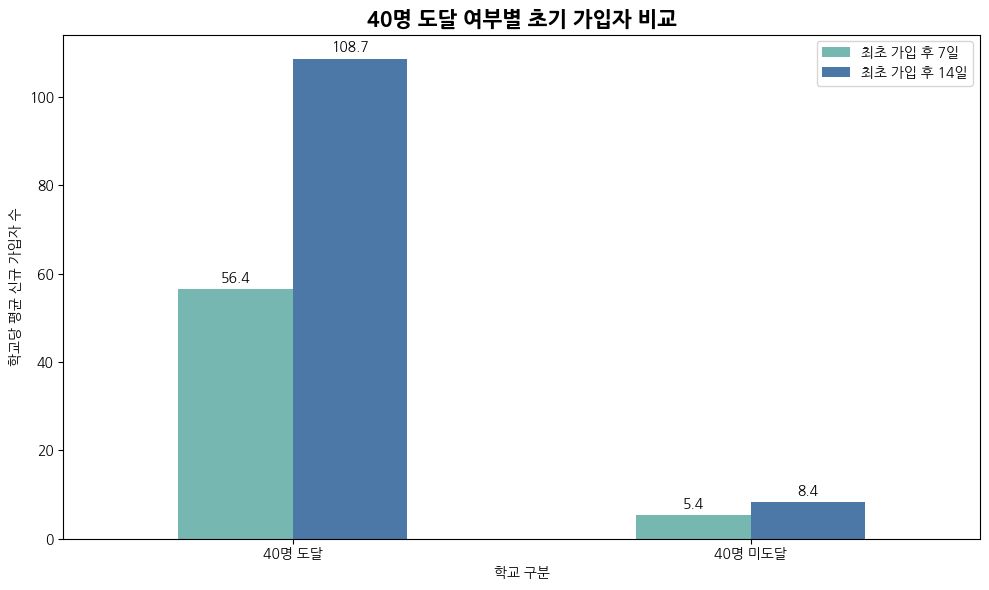

In [ ]:
# 40명 도달 여부별 초기 7일·14일 가입
school_signup = growth_users[
    ['school_id', 'user_id', 'signup_date']
].merge(
    school_first_signup,
    on='school_id',
    how='left',
)
school_signup['최초가입후_경과일'] = (
    school_signup['signup_date'] - school_signup['최초가입일']
).dt.days

initial_signup = (
    school_signup.groupby('school_id')
    .agg(
        초기7일가입자=(
            '최초가입후_경과일',
            lambda x: x.between(0, 6).sum(),
        ),
        초기14일가입자=(
            '최초가입후_경과일',
            lambda x: x.between(0, 13).sum(),
        ),
        가입발생일수=('signup_date', 'nunique'),
    )
    .reset_index()
)
school_activation = school_activation.merge(
    initial_signup,
    on='school_id',
    how='left',
)

reach_comparison = (
    school_activation.groupby('40명_도달여부')
    .agg(
        학교수=('school_id', 'nunique'),
        초기7일가입자_평균=('초기7일가입자', 'mean'),
        초기7일가입자_중앙값=('초기7일가입자', 'median'),
        초기14일가입자_평균=('초기14일가입자', 'mean'),
        초기14일가입자_중앙값=('초기14일가입자', 'median'),
        가입발생일수_평균=('가입발생일수', 'mean'),
        최종가입자수_평균=('최종가입자수', 'mean'),
        최종가입자수_중앙값=('최종가입자수', 'median'),
    )
    .reset_index()
)
display(reach_comparison.round(2))

growth_plot_data = reach_comparison.set_index('40명_도달여부')
ax = growth_plot_data[
    ['초기7일가입자_평균', '초기14일가입자_평균']
].plot(
    kind='bar',
    figsize=(10, 6),
    color=['#76B7B2', '#4C78A8'],
)
plt.title('40명 도달 여부별 초기 가입자 비교', fontsize=15, fontweight='bold')
plt.xlabel('학교 구분')
plt.ylabel('학교당 평균 신규 가입자 수')
plt.xticks(rotation=0)
plt.legend(['최초 가입 후 7일', '최초 가입 후 14일'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

plt.close('all')


- 초기 7일 가입자 중앙값은 40명 도달 학교 20명, 미도달 학교 3명이다. 초기 14일에는 각각 94명과 5명으로 격차가 더 커졌다.


### 3-1-3. 40명 도달 전후의 가입 곡선

- 2023년 4~5월에 40명에 도달한 학교의 전후 14일을 맞춘다.
- 가입이 없는 날도 0명으로 채워 같은 길이로 집계한다.


In [ ]:
# 4~5월 도달 학교의 D0 전후 패널
viral_reached_schools = school_activation.loc[
    school_activation['40명_도달일'].between(
        pd.Timestamp('2023-04-01'),
        pd.Timestamp('2023-05-31'),
    ),
    ['school_id', '40명_도달일'],
].copy()

event_signup = school_daily_signup.merge(
    viral_reached_schools,
    on='school_id',
    how='inner',
)
event_signup['relative_day'] = (
    event_signup['signup_date'] - event_signup['40명_도달일']
).dt.days
event_signup = event_signup.loc[
    event_signup['relative_day'].between(-14, 14)
].copy()

growth_school_ids = viral_reached_schools['school_id'].unique()
growth_relative_days = np.arange(-14, 15)
balanced_school_day = pd.MultiIndex.from_product(
    [growth_school_ids, growth_relative_days],
    names=['school_id', 'relative_day'],
).to_frame(index=False)
balanced_school_day = balanced_school_day.merge(
    event_signup[['school_id', 'relative_day', '일별가입자수']],
    on=['school_id', 'relative_day'],
    how='left',
)
balanced_school_day['일별가입자수'] = (
    balanced_school_day['일별가입자수'].fillna(0)
)

print('4~5월 40명 도달 학교:', f'{len(growth_school_ids):,}개')
print('학교·일 데이터:', f'{len(balanced_school_day):,}행')


4~5월 40명 도달 학교: 3,796개
학교·일 데이터: 110,084행


- 3,796개 학교에 대해 D-14~D+14의 29일을 구성했다. 신규 가입이 없는 학교·일도 포함한 비교다.


,relative_day,일평균_신규가입자,중앙값_신규가입자,가입발생_학교수,일별_최대가입자,가입발생_학교비율(%)
0,-14,0.21,0.0,397,15.0,10.46
1,-13,0.23,0.0,419,20.0,11.04
2,-12,0.29,0.0,496,19.0,13.07
3,-11,0.35,0.0,554,21.0,14.59
4,-10,0.38,0.0,637,25.0,16.78
5,-9,0.49,0.0,770,30.0,20.28
6,-8,0.64,0.0,918,30.0,24.18
7,-7,0.85,0.0,1131,26.0,29.79
8,-6,1.05,0.0,1387,30.0,36.54
9,-5,1.25,0.0,1492,29.0,39.30


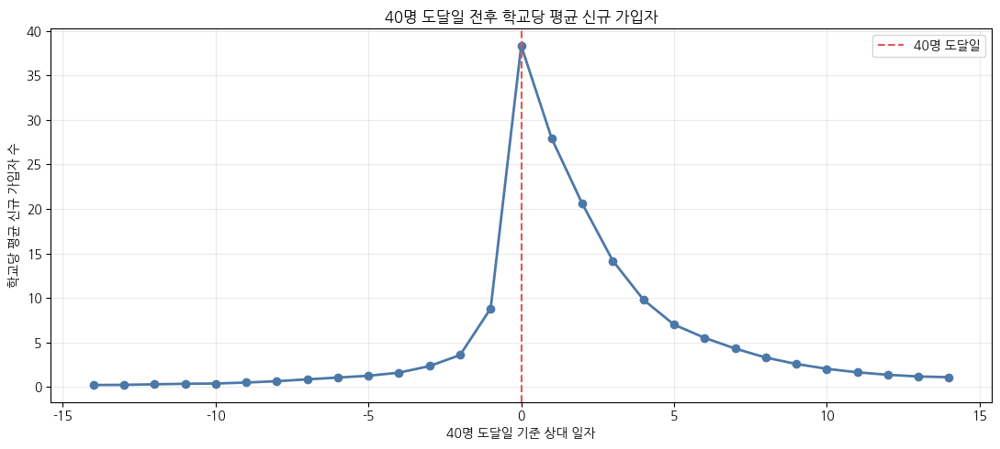

In [ ]:
# 40명 도달 전후 일별 가입 변화
event_curve = (
    balanced_school_day.groupby('relative_day')
    .agg(
        일평균_신규가입자=('일별가입자수', 'mean'),
        중앙값_신규가입자=('일별가입자수', 'median'),
        가입발생_학교수=('일별가입자수', lambda x: (x > 0).sum()),
        일별_최대가입자=('일별가입자수', 'max'),
    )
    .reset_index()
)
reached_school_count = viral_reached_schools['school_id'].nunique()
event_curve['가입발생_학교비율(%)'] = (
    event_curve['가입발생_학교수'] / reached_school_count * 100
)
growth_event_numeric = event_curve.select_dtypes(include='number').columns
event_curve[growth_event_numeric] = event_curve[growth_event_numeric].round(2)
display(event_curve)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(
    event_curve['relative_day'],
    event_curve['일평균_신규가입자'],
    marker='o',
    linewidth=2,
    color='#4C78A8',
)
ax.axvline(0, color='#E45756', linestyle='--', linewidth=1.5, label='40명 도달일')
ax.set_title('40명 도달일 전후 학교당 평균 신규 가입자')
ax.set_xlabel('40명 도달일 기준 상대 일자')
ax.set_ylabel('학교당 평균 신규 가입자 수')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.close('all')


- 학교당 평균 신규 가입자는 D0 38.35명, D+1 27.90명, D+7 4.31명, D+14 1.09명으로 줄었다.
- 가입이 발생한 학교 비율도 D+1 96.26%에서 D+14 43.23%로 낮아졌다. 시간이 지나며 가입 규모와 가입이 발생하는 학교 수가 함께 감소했다.


### 3-1-4. 도달 직후와 둘째 주 비교

- D0를 빼고 도달 이전·직전·첫째 주·둘째 주를 각각 7일로 나눈다.
- 구간별 추가 가입자 수와 가입이 발생한 날의 수를 집계한다.


In [ ]:
# D0 제외 전후 네 구간별 학교 집계
def classify_growth_period(relative_day):
    if -14 <= relative_day <= -8:
        return '도달 이전 D-14~-8'
    if -7 <= relative_day <= -1:
        return '도달 직전 D-7~-1'
    if 1 <= relative_day <= 7:
        return '도달 직후 D+1~+7'
    if 8 <= relative_day <= 14:
        return '도달 후기 D+8~+14'
    return np.nan

growth_period_order = [
    '도달 이전 D-14~-8',
    '도달 직전 D-7~-1',
    '도달 직후 D+1~+7',
    '도달 후기 D+8~+14',
]
period_data = balanced_school_day.loc[
    balanced_school_day['relative_day'] != 0
].copy()
period_data['기간'] = period_data['relative_day'].apply(classify_growth_period)
period_data['기간'] = pd.Categorical(
    period_data['기간'],
    categories=growth_period_order,
    ordered=True,
)

school_period_summary = (
    period_data.groupby(['school_id', '기간'], observed=True)
    .agg(
        구간추가가입자=('일별가입자수', 'sum'),
        일평균가입자=('일별가입자수', 'mean'),
        가입발생일수=('일별가입자수', lambda x: (x > 0).sum()),
    )
    .reset_index()
)
display(school_period_summary.head(12))


,school_id,기간,구간추가가입자,일평균가입자,가입발생일수
0,1,도달 이전 D-14~-8,9.0,1.285714,5
1,1,도달 직전 D-7~-1,14.0,2.000000,5
2,1,도달 직후 D+1~+7,7.0,1.000000,3
3,1,도달 후기 D+8~+14,7.0,1.000000,5
4,4,도달 이전 D-14~-8,0.0,0.000000,0
5,4,도달 직전 D-7~-1,15.0,2.142857,3
6,4,도달 직후 D+1~+7,169.0,24.142857,7
7,4,도달 후기 D+8~+14,4.0,0.571429,3
8,5,도달 이전 D-14~-8,0.0,0.000000,0
9,5,도달 직전 D-7~-1,19.0,2.714286,5


- D0를 제외한 네 구간에서 학교별 추가 가입자 수와 가입 발생일 수를 집계했다.


,기간,학교당_평균추가가입자,학교당_중앙값추가가입자,일평균_신규가입자,평균_가입발생일수,가입발생_학교일비율(%)
0,도달 이전 D-14~-8,2.59,0.0,0.37,1.10,15.77
1,도달 직전 D-7~-1,19.49,20.0,2.78,3.64,52.02
2,도달 직후 D+1~+7,89.28,76.0,12.75,6.29,89.89
3,도달 후기 D+8~+14,13.17,8.0,1.88,4.01,57.34


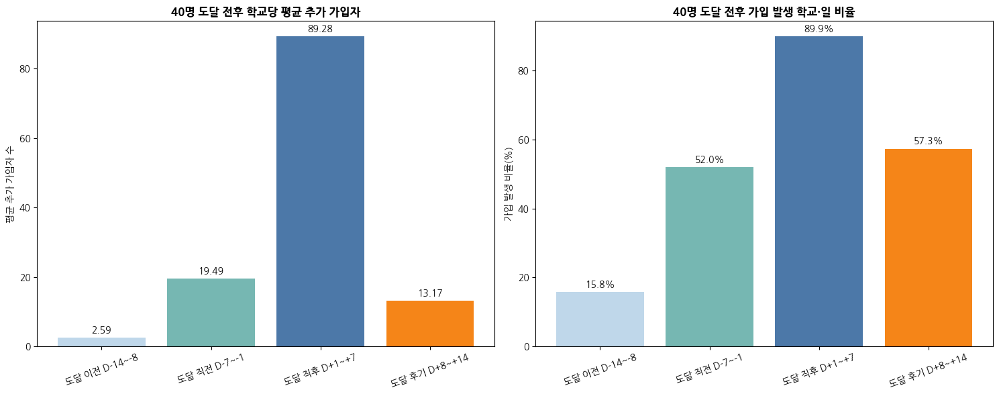

In [ ]:
# 도달 직후·둘째 주 추가 가입 비교
period_comparison = (
    school_period_summary.groupby('기간', observed=True)
    .agg(
        학교당_평균추가가입자=('구간추가가입자', 'mean'),
        학교당_중앙값추가가입자=('구간추가가입자', 'median'),
        일평균_신규가입자=('일평균가입자', 'mean'),
        평균_가입발생일수=('가입발생일수', 'mean'),
    )
    .reindex(growth_period_order)
    .reset_index()
)
growth_active_rate = (
    period_data.assign(가입발생=period_data['일별가입자수'].gt(0))
    .groupby('기간', observed=True)['가입발생']
    .mean()
    .mul(100)
    .reindex(growth_period_order)
    .rename('가입발생_학교일비율(%)')
    .reset_index()
)
period_comparison = period_comparison.merge(
    growth_active_rate,
    on='기간',
    how='left',
)
growth_period_numeric = period_comparison.select_dtypes(include='number').columns
period_comparison[growth_period_numeric] = (
    period_comparison[growth_period_numeric].round(2)
)
display(period_comparison)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
growth_colors = ['#BFD7EA', '#76B7B2', '#4C78A8', '#F58518']
bars1 = axes[0].bar(
    period_comparison['기간'],
    period_comparison['학교당_평균추가가입자'],
    color=growth_colors,
)
axes[0].set_title('40명 도달 전후 학교당 평균 추가 가입자', fontweight='bold')
axes[0].set_ylabel('평균 추가 가입자 수')
axes[0].tick_params(axis='x', rotation=20)
axes[0].bar_label(bars1, fmt='%.2f', padding=3)

bars2 = axes[1].bar(
    period_comparison['기간'],
    period_comparison['가입발생_학교일비율(%)'],
    color=growth_colors,
)
axes[1].set_title('40명 도달 전후 가입 발생 학교·일 비율', fontweight='bold')
axes[1].set_ylabel('가입 발생 비율(%)')
axes[1].tick_params(axis='x', rotation=20)
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

plt.close('all')


- 학교당 평균 추가 가입자는 첫째 주 89.28명에서 둘째 주 13.17명으로 감소했다.
- 가입이 발생한 학교·일 비율도 89.89%에서 57.34%로 낮아졌다. 둘째 주에는 신규 가입이 없는 날이 늘었다.


### 3-1-5. 학교별 확산 유형

- 첫째 주·둘째 주 추가 가입자 중앙값을 기준으로 네 유형을 만든다.
- 관측한 2주간의 가입 경로를 요약한 분류다. 기존 사용자의 이용 빈도나 장기 유지 성과는 별도로 살펴봐야 한다.


In [ ]:
# 첫째 주·둘째 주 가입 기준 확산 유형
school_diffusion = (
    school_period_summary.pivot(
        index='school_id',
        columns='기간',
        values='구간추가가입자',
    )
    .reset_index()
)
school_diffusion.columns.name = None
school_diffusion = school_diffusion.rename(columns={
    '도달 이전 D-14~-8': '도달이전_D14_D8',
    '도달 직전 D-7~-1': '도달직전_D7_D1',
    '도달 직후 D+1~+7': '첫째주_D1_D7',
    '도달 후기 D+8~+14': '둘째주_D8_D14',
})
growth_period_columns = [
    '도달이전_D14_D8',
    '도달직전_D7_D1',
    '첫째주_D1_D7',
    '둘째주_D8_D14',
]
school_diffusion[growth_period_columns] = (
    school_diffusion[growth_period_columns].fillna(0)
)
school_diffusion = school_diffusion.merge(
    school_activation[
        ['school_id', '40명_도달소요일', '최종가입자수']
    ],
    on='school_id',
    how='left',
)

first_week_median = school_diffusion['첫째주_D1_D7'].median()
second_week_median = school_diffusion['둘째주_D8_D14'].median()
growth_conditions = [
    (
        school_diffusion['첫째주_D1_D7'].ge(first_week_median)
        & school_diffusion['둘째주_D8_D14'].ge(second_week_median)
    ),
    (
        school_diffusion['첫째주_D1_D7'].ge(first_week_median)
        & school_diffusion['둘째주_D8_D14'].lt(second_week_median)
    ),
    (
        school_diffusion['첫째주_D1_D7'].lt(first_week_median)
        & school_diffusion['둘째주_D8_D14'].ge(second_week_median)
    ),
]
growth_choices = ['지속 확산형', '단기 폭발형', '후발 확산형']
school_diffusion['확산유형'] = np.select(
    growth_conditions,
    growth_choices,
    default='저확산형',
)

print('첫째 주 분류 기준:', first_week_median)
print('둘째 주 분류 기준:', second_week_median)
type_count = (
    school_diffusion['확산유형']
    .value_counts()
    .rename_axis('확산유형')
    .reset_index(name='학교수')
)
type_count['학교비율(%)'] = (
    type_count['학교수'] / type_count['학교수'].sum() * 100
).round(2)
display(type_count)


첫째 주 분류 기준: 76.0
둘째 주 분류 기준: 8.0


,확산유형,학교수,학교비율(%)
0,지속 확산형,1382,36.41
1,저확산형,1288,33.93
2,후발 확산형,586,15.44
3,단기 폭발형,540,14.23


- 첫째 주 76명, 둘째 주 8명을 각각 기준으로 삼았다. 두 기준 이상은 지속 확산형, 모두 미만은 저확산형이다.
- 첫째 주만 기준 이상이면 단기 폭발형, 둘째 주만 기준 이상이면 후발 확산형이다.
- 지속 확산형은 1,382개(36.41%), 저확산형은 1,288개(33.93%)다.


### 3-1-6. 확산 유형별 성장 경로 정리

- 유형별 첫째 주·둘째 주 가입자와 최종 가입 규모를 나란히 본다.
- 초반 유입이 컸던 학교에서 추가 가입이 얼마나 이어졌는지 살펴본다.


In [ ]:
# 확산 유형별 가입 규모·도달 속도
diffusion_summary = (
    school_diffusion.groupby('확산유형')
    .agg(
        학교수=('school_id', 'nunique'),
        도달직전_평균가입자=('도달직전_D7_D1', 'mean'),
        첫째주_평균가입자=('첫째주_D1_D7', 'mean'),
        둘째주_평균가입자=('둘째주_D8_D14', 'mean'),
        도달소요일_중앙값=('40명_도달소요일', 'median'),
        최종가입자수_중앙값=('최종가입자수', 'median'),
    )
    .reset_index()
)
diffusion_summary['학교비율(%)'] = (
    diffusion_summary['학교수'] / diffusion_summary['학교수'].sum() * 100
)
growth_summary_numeric = diffusion_summary.select_dtypes(include='number').columns
diffusion_summary[growth_summary_numeric] = (
    diffusion_summary[growth_summary_numeric].round(2)
)
diffusion_summary = diffusion_summary[
    [
        '확산유형',
        '학교수',
        '학교비율(%)',
        '도달직전_평균가입자',
        '첫째주_평균가입자',
        '둘째주_평균가입자',
        '도달소요일_중앙값',
        '최종가입자수_중앙값',
    ]
].sort_values('학교수', ascending=False)
display(diffusion_summary)

team7_release_unused('123', '3-1 완료')


,확산유형,학교수,학교비율(%),도달직전_평균가입자,첫째주_평균가입자,둘째주_평균가입자,도달소요일_중앙값,최종가입자수_중앙값
2,지속 확산형,1382,36.41,18.13,146.25,24.00,8.0,235.0
1,저확산형,1288,33.93,20.73,34.27,2.79,11.0,91.0
3,후발 확산형,586,15.44,22.36,47.09,18.61,8.0,124.0
0,단기 폭발형,540,14.23,16.92,120.51,4.29,9.0,185.0


[3-1 완료] 사용이 끝난 변수 33개 정리
[3-1 완료] Python 사용 RAM 3.24 GB / 시스템 여유 RAM 9.00 GB


- 지속 확산형과 단기 폭발형의 첫째 주 평균 추가 가입자는 146.25명과 120.51명, 둘째 주는 24.00명과 4.29명이다.
- 후발 확산형은 첫째 주 평균 47.09명, 둘째 주 18.61명이다. ‘후발’은 전주 대비 증가가 아니라 둘째 주 분류 기준을 넘었다는 뜻이다.


## 3-2. Network

- 첫 친구 요청이 시작되는 속도와 둘째 주까지 이어지는 관계 행동을 살펴본다.
- 학교 관계망의 구조와 Growth의 확산 유형을 함께 놓고 본다.


### 3-2-1. 관계 데이터와 분석 범위

- 정제한 친구 요청·사용자·학교·연락처 마트를 사용한다. 학교·친구 정보는 현재 상태, A·P·R은 요청의 최종 상태다.
- D0는 기록상 40명 도달일이다. 과거 소속이나 실제 수락 시각을 복원한 자료는 없다.


In [ ]:
# Network 정제 마트 연결·분석 설정
network_processed_dir = Path(
    globals().get('NETWORK_OUTPUT_DIR', '/content/team7_processed/viral_school')
)
NETWORK_FILES = {
    'event': network_processed_dir / 'mart_friend_request_event_v2_clean.csv.gz',
    'pair': network_processed_dir / 'mart_friend_request_pair_summary_v2_clean.csv.gz',
    'school_daily': network_processed_dir / 'mart_school_viral_daily_v2_clean.csv.gz',
    'acquisition': network_processed_dir / 'mart_user_acquisition_profile_v2_clean.csv.gz',
    'contact': network_processed_dir / 'mart_user_contact_record_v2_clean.csv.gz',
    'profile': network_processed_dir / 'mart_user_viral_profile_v2_clean.csv.gz',
}
network_missing = [path for path in NETWORK_FILES.values() if not path.exists()]
if network_missing:
    raise FileNotFoundError(
        'Network 분석에 필요한 2-1 정제 파일이 없습니다. '
        '같은 코랩 런타임에서 2-1 전처리를 먼저 완료해야 합니다:\n- '
        + '\n- '.join(str(path) for path in network_missing)
    )

try:
    network_con.close()
except (NameError, AttributeError):
    pass
network_con = team7_connect('network')
network_con.execute('SET threads=2')
network_con.execute('SET preserve_insertion_order=false')
network_con.execute('PRAGMA disable_progress_bar')

def network_csv_sql(path):
    return (
        "read_csv_auto('" + path.as_posix()
        + "', header=true, sample_size=200000, nullstr='\\N')"
    )

for name, path in NETWORK_FILES.items():
    network_con.execute(
        f'CREATE OR REPLACE VIEW {name} AS SELECT * FROM {network_csv_sql(path)}'
    )

NETWORK_COLORS = {
    'navy': '#244A73', 'blue': '#4E83B6', 'orange': '#F28E5B',
    'green': '#4E9F78', 'gray': '#8A96A3', 'red': '#C94C4C',
}
COLORS = NETWORK_COLORS
print('Network 정제 마트 연결 완료:', len(NETWORK_FILES), '개')


Network 정제 마트 연결 완료: 6 개


In [ ]:
# 관계 마트 모집단·기간·기록 오류 확인
scope = network_con.execute('''
SELECT '사용자 프로필' AS object,
       COUNT(*) AS row_count,
       SUM(analysis_eligible_nonstaff_flag) AS eligible_count,
       MIN(signup_at) AS min_datetime,
       MAX(signup_at) AS max_datetime,
       COUNT(DISTINCT TRY_CAST(current_school_id AS BIGINT)) AS school_count
FROM profile
UNION ALL
SELECT '친구요청 이벤트', COUNT(*), SUM(analysis_eligible_request_flag),
       MIN(request_created_at_raw), MAX(request_created_at_raw),
       COUNT(DISTINCT sender_current_school_id)
FROM event
UNION ALL
SELECT '학교×일 패널', COUNT(*), SUM(analysis_eligible_school_day_flag),
       MIN(activity_date), MAX(activity_date), COUNT(DISTINCT school_id)
FROM school_daily
UNION ALL
SELECT '연락처 스냅샷', COUNT(*), SUM(analysis_eligible_nonstaff_flag),
       NULL, NULL, COUNT(DISTINCT contact_owner_current_school_id)
FROM contact
''').fetchdf()

qa = network_con.execute('''
SELECT
    COUNT(*) AS request_rows,
    SUM(self_request_flag) AS self_requests,
    SUM(CASE WHEN status_code_valid_flag <> 1 THEN 1 ELSE 0 END) AS invalid_status,
    SUM(CASE WHEN request_timestamp_valid_flag <> 1 THEN 1 ELSE 0 END) AS invalid_timestamp,
    SUM(CASE WHEN negative_update_interval_flag = 1 THEN 1 ELSE 0 END) AS negative_update_interval,
    SUM(CASE WHEN sender_known_user_flag <> 1 OR receiver_known_user_flag <> 1 THEN 1 ELSE 0 END) AS unknown_endpoint,
    SUM(CASE WHEN analysis_eligible_request_flag = 1 THEN 1 ELSE 0 END) AS eligible_requests
FROM event
''').fetchdf()

reached = network_con.execute('''
SELECT
    COUNT(DISTINCT school_id) AS observed_schools,
    COUNT(DISTINCT CASE WHEN current_roster_reached_40_flag = 1 THEN school_id END) AS reached_40_schools,
    MIN(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS first_d0,
    MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS last_d0
FROM school_daily
''').fetchdf()

display(scope)
display(qa)
display(reached)


,object,row_count,eligible_count,min_datetime,max_datetime,school_count
0,사용자 프로필,677085,677081.0,2023-03-29 03:44:14.047130,2024-05-09 08:31:17.710824,5551
1,친구요청 이벤트,17147175,17147175.0,2023-04-17 18:29:11.000000,2024-05-09 09:21:47.000000,5404
2,학교×일 패널,2428008,2052369.0,2023-03-29 00:00:00.000000,2024-05-09 00:00:00.000000,5951
3,연락처 스냅샷,5063,5063.0,NaT,NaT,10


,request_rows,self_requests,invalid_status,invalid_timestamp,negative_update_interval,unknown_endpoint,eligible_requests
0,17147175,0.0,0.0,0.0,0.0,0.0,17147175.0


,observed_schools,reached_40_schools,first_d0,last_d0
0,5951,3896,2023-04-19 06:20:07.938133,2023-09-28 09:15:43.538435


- 일반 사용자 677,081명, 친구 요청 17,147,175건이 대상이다. 요청 상태·시각·사용자 연결 검사에서 오류가 발견되지 않았다.
- 학교 일별 마트의 40명 도달 학교는 3,896개로 Growth보다 1개 적다. 연락처 스냅샷은 10개 학교의 5,063행이다.


### 3-2-2. 가입 이후 첫 관계 행동

- 가입·요청 추이, 요청 경험 비율, 첫 요청까지 걸린 시간을 살펴본다.
- 사용자별 요청량의 분포와 반복 요청도 함께 본다.


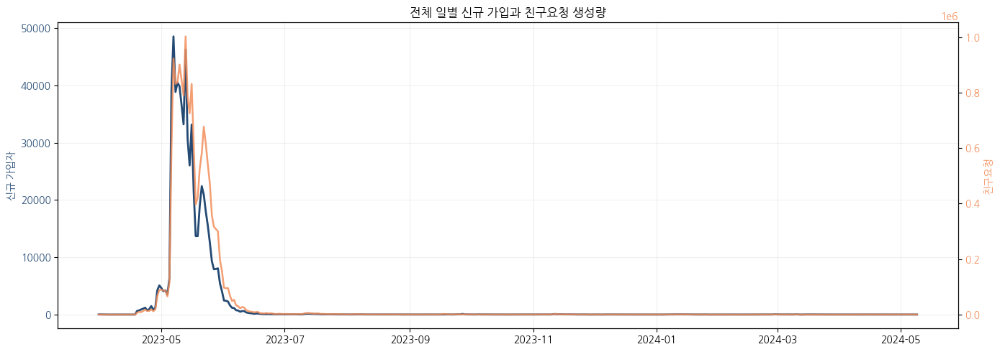

5월 신규 가입: 635,478명
5월 친구요청: 15,989,482건
일별 신규 가입과 친구요청 Spearman ρ: 0.916


In [ ]:
# 일별 가입자·친구요청 추이
daily = network_con.execute('''
SELECT CAST(activity_date AS DATE) AS activity_date,
       SUM(new_nonstaff_account_count_current_roster) AS new_users,
       SUM(sent_request_created_count) AS sent_requests,
       SUM(sent_request_user_count) AS sender_days,
       SUM(sent_within_school_count_current) AS within_school_requests,
       SUM(sent_created_final_accepted_count) AS eventual_accepted_requests
FROM school_daily
WHERE analysis_eligible_school_day_flag = 1
GROUP BY 1
ORDER BY 1
''').fetchdf()
daily["activity_date"] = pd.to_datetime(daily["activity_date"])
daily["same_school_share"] = daily["within_school_requests"] / daily["sent_requests"].replace(0, np.nan)
daily["eventual_acceptance_share"] = daily["eventual_accepted_requests"] / daily["sent_requests"].replace(0, np.nan)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily.activity_date, daily.new_users, color=COLORS["navy"], lw=2, label="신규 가입자")
ax1.set_ylabel("신규 가입자", color=COLORS["navy"])
ax1.tick_params(axis="y", labelcolor=COLORS["navy"])
ax2 = ax1.twinx()
ax2.plot(daily.activity_date, daily.sent_requests, color=COLORS["orange"], lw=1.8, alpha=.85, label="친구요청")
ax2.set_ylabel("친구요청", color=COLORS["orange"])
ax2.tick_params(axis="y", labelcolor=COLORS["orange"])
ax1.set_title("전체 일별 신규 가입과 친구요청 생성량")
ax1.grid(alpha=.2)
plt.tight_layout()
plt.show()

may = daily[daily.activity_date.between("2023-05-01", "2023-05-31")]
print(f"5월 신규 가입: {may.new_users.sum():,.0f}명")
print(f"5월 친구요청: {may.sent_requests.sum():,.0f}건")
print(f"일별 신규 가입과 친구요청 Spearman ρ: {stats.spearmanr(daily.new_users, daily.sent_requests, nan_policy='omit').statistic:.3f}")

plt.close('all')


- 학교 일별 마트에서 5월 가입자는 635,478명, 친구 요청은 15,989,482건이다.
- 일별 가입자와 요청량의 순위상관 0.916은 5월만이 아니라 전체 일별 분석 기간에서 계산한 값이다. Viral의 5월 상관 0.965와는 기간·학교 범위가 다르다.


,stage,users,share_of_users
0,분석 가능 가입자,677081.0,1.0000
1,요청 발송 또는 수신,673705.0,0.9950
2,요청 발송,649072.0,0.9586
3,요청 수신,660841.0,0.9760
4,발송 요청 최종 수락 경험,640672.0,0.9462
5,수신 요청 최종 수락 경험,560506.0,0.8278


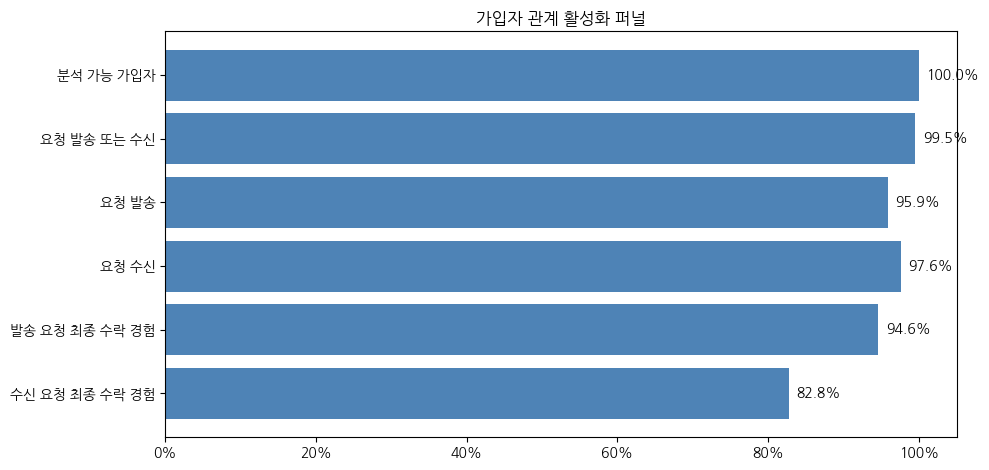

In [ ]:
# 가입자별 요청 발송·수신·수락 경험
funnel = network_con.execute('''
WITH p AS (
    SELECT * FROM profile WHERE analysis_eligible_nonstaff_flag = 1
)
SELECT '분석 가능 가입자' AS stage, COUNT(*) AS users FROM p
UNION ALL SELECT '요청 발송 또는 수신', SUM(has_any_friend_request_activity_flag) FROM p
UNION ALL SELECT '요청 발송', SUM(CASE WHEN sent_request_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '요청 수신', SUM(CASE WHEN received_request_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '발송 요청 최종 수락 경험', SUM(CASE WHEN sent_final_accepted_count > 0 THEN 1 ELSE 0 END) FROM p
UNION ALL SELECT '수신 요청 최종 수락 경험', SUM(CASE WHEN received_final_accepted_count > 0 THEN 1 ELSE 0 END) FROM p
''').fetchdf()
funnel["share_of_users"] = funnel.users / funnel.loc[funnel.stage.eq("분석 가능 가입자"), "users"].iloc[0]
display(funnel.round(4))

plt.figure(figsize=(10, 4.8))
order = funnel.iloc[::-1]
plt.barh(order.stage, order.share_of_users, color=COLORS["blue"])
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.xlim(0, 1.05)
for y, v in enumerate(order.share_of_users):
    plt.text(v + .01, y, f"{v:.1%}", va="center")
plt.title("가입자 관계 활성화 퍼널")
plt.tight_layout()
plt.show()

plt.close('all')


- 일반 사용자의 99.50%가 요청을 보내거나 받았다. 발송 경험은 95.86%, 수신 경험은 97.60%다.
- 발송 요청의 최종 수락 경험은 94.62%, 수신 요청의 최종 수락 경험은 82.78%다. 모두 같은 사용자 모집단의 경험 비율이며 순차 전환율은 아니다.


,metric,all_eligible_users,observed_users,ever_observed_share,within_1min_all_users,within_5min_all_users,within_1h_all_users,within_24h_all_users,median_minutes,p90_hours,p99_hours
0,가입→첫 요청 발송,677081,649072,0.9586,0.8000,0.8598,0.8795,0.9085,0.2377,0.1061,218.9537
1,가입→첫 요청 수신,677081,660841,0.9760,0.0591,0.1920,0.5300,0.8645,44.6922,27.1777,290.5110


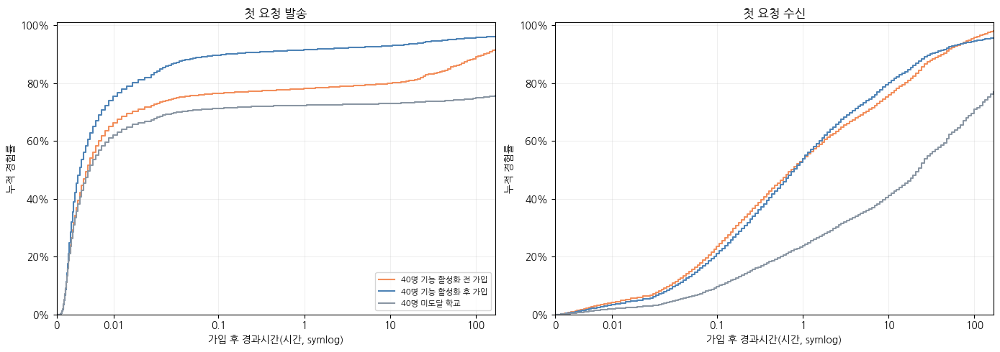

,metric,logrank_chi2,p_value,pre_40_7d_experience_rate,post_40_7d_experience_rate,post_minus_pre_difference_pp,difference_ci_low_pp,difference_ci_high_pp
0,first_sent_hours,10766.539300,0.000000,0.916997,0.961612,4.461473,4.312963,4.609982
1,first_received_hours,4.332185,0.037398,0.980406,0.957167,-2.323842,-2.413193,-2.234490


In [ ]:
# 가입 후 첫 발송·수신 시간과 학교 단계
timing = network_con.execute('''
SELECT
    user_id,
    signup_at,
    TRY_CAST(first_sent_request_at_raw AS TIMESTAMP) AS first_sent_at,
    TRY_CAST(first_received_request_at_raw AS TIMESTAMP) AS first_received_at,
    TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS school_d0,
    CASE
        WHEN TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) IS NULL THEN 'SCHOOL_NOT_OBSERVED_REACHED_40'
        WHEN signup_at < TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) THEN 'BEFORE_OBSERVED_40TH'
        ELSE 'ON_OR_AFTER_OBSERVED_40TH'
    END AS signup_observed_40_phase,
    sent_request_count,
    received_request_count,
    sent_request_first_24h_count,
    sent_request_first_72h_count,
    sent_request_first_7d_count,
    received_request_first_24h_count,
    received_request_first_72h_count,
    received_request_first_7d_count
FROM profile
WHERE analysis_eligible_nonstaff_flag = 1
''').fetchdf()
for col in ["signup_at", "first_sent_at", "first_received_at", "school_d0"]:
    timing[col] = pd.to_datetime(timing[col], errors="coerce")
timing["first_sent_hours"] = (timing.first_sent_at - timing.signup_at).dt.total_seconds() / 3600
timing["first_received_hours"] = (timing.first_received_at - timing.signup_at).dt.total_seconds() / 3600
timing["phase_label"] = timing.signup_observed_40_phase.map({
    "BEFORE_OBSERVED_40TH": "40명 기능 활성화 전 가입",
    "ON_OR_AFTER_OBSERVED_40TH": "40명 기능 활성화 후 가입",
    "SCHOOL_NOT_OBSERVED_REACHED_40": "40명 미도달 학교",
    "NO_CURRENT_SCHOOL": "학교 없음",
})

def timing_summary(series, label):
    valid = series[series.ge(0)].dropna()
    return {
        "metric": label,
        "all_eligible_users": len(series),
        "observed_users": len(valid),
        "ever_observed_share": len(valid)/len(series),
        "within_1min_all_users": series.ge(0).mul(series.le(1/60)).mean(),
        "within_5min_all_users": series.ge(0).mul(series.le(5/60)).mean(),
        "within_1h_all_users": series.ge(0).mul(series.le(1)).mean(),
        "within_24h_all_users": series.ge(0).mul(series.le(24)).mean(),
        "median_minutes": valid.median() * 60,
        "p90_hours": valid.quantile(.9),
        "p99_hours": valid.quantile(.99),
    }

speed_summary = pd.DataFrame([
    timing_summary(timing.first_sent_hours, "가입→첫 요청 발송"),
    timing_summary(timing.first_received_hours, "가입→첫 요청 수신"),
])
display(speed_summary.round(4))

def km_curve(durations, observed, horizon=168):

    raw = np.asarray(durations, float)
    e = np.asarray(observed, bool) & np.isfinite(raw) & (raw >= 0) & (raw <= horizon)
    grid = np.unique(np.r_[0, np.geomspace(1/3600, horizon, 180)])
    incidence = np.array([np.mean(e & (raw <= t)) for t in grid])
    return pd.DataFrame({"hours": grid, "survival": 1-incidence})

def logrank_test(t1, e1, t2, e2, horizon=168):
    raw1, raw2 = np.asarray(t1, float), np.asarray(t2, float)
    e1 = np.asarray(e1, bool) & np.isfinite(raw1) & (raw1 >= 0) & (raw1 <= horizon)
    e2 = np.asarray(e2, bool) & np.isfinite(raw2) & (raw2 >= 0) & (raw2 <= horizon)
    t1 = np.where(e1, raw1, horizon); t2 = np.where(e2, raw2, horizon)
    ev1, d1c = np.unique(t1[e1], return_counts=True)
    ev2, d2c = np.unique(t2[e2], return_counts=True)
    times = np.union1d(ev1, ev2)
    d1 = np.zeros(len(times)); d2 = np.zeros(len(times))
    d1[np.searchsorted(times, ev1)] = d1c
    d2[np.searchsorted(times, ev2)] = d2c
    s1, s2 = np.sort(t1), np.sort(t2)
    n1 = len(s1) - np.searchsorted(s1, times, side="left")
    n2 = len(s2) - np.searchsorted(s2, times, side="left")
    n, d = n1+n2, d1+d2
    valid = n > 1
    expected1 = np.divide(d*n1, n, out=np.zeros_like(d), where=n>0)
    variance = np.divide(n1*n2*d*(n-d), n*n*(n-1), out=np.zeros_like(d), where=valid)
    oe = np.sum((d1-expected1)[valid]); var = np.sum(variance[valid])
    chi2 = oe*oe/var if var > 0 else np.nan
    return chi2, stats.chi2.sf(chi2, 1) if np.isfinite(chi2) else np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase_order = ["40명 기능 활성화 전 가입", "40명 기능 활성화 후 가입", "40명 미도달 학교"]
for ax, col, title in zip(axes, ["first_sent_hours", "first_received_hours"], ["첫 요청 발송", "첫 요청 수신"]):
    for phase, color in zip(phase_order, [COLORS["orange"], COLORS["blue"], COLORS["gray"]]):
        sub = timing[timing.phase_label.eq(phase)]
        durations = sub[col].fillna(168).clip(lower=0)
        observed = sub[col].notna() & sub[col].ge(0)
        km = km_curve(durations, observed, 168)
        ax.step(km.hours, 1-km.survival, where="post", label=phase, color=color)
    ax.set_xscale("symlog", linthresh=1/60)
    team7_plain_log_ticks(ax, 'x')
    ax.set_xlim(0, 168)
    ax.set_ylim(0, 1.01)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("가입 후 경과시간(시간, symlog)")
    ax.set_ylabel("누적 경험률")
    ax.set_title(title)
    ax.grid(alpha=.2)
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

tests = []
def proportion_diff_ci(x1,n1,x2,n2):
    p1,p2=x1/n1,x2/n2
    se=np.sqrt(p1*(1-p1)/n1+p2*(1-p2)/n2)
    diff=p2-p1
    return diff,diff-1.96*se,diff+1.96*se
for col in ["first_sent_hours", "first_received_hours"]:
    a = timing[timing.phase_label.eq("40명 기능 활성화 전 가입")]
    b = timing[timing.phase_label.eq("40명 기능 활성화 후 가입")]
    ta, ea = a[col].fillna(168).clip(lower=0), a[col].notna() & a[col].ge(0)
    tb, eb = b[col].fillna(168).clip(lower=0), b[col].notna() & b[col].ge(0)
    chi2, p = logrank_test(ta, ea, tb, eb)
    x1=int((ea & ta.le(168)).sum()); x2=int((eb & tb.le(168)).sum())
    diff,lo,hi=proportion_diff_ci(x1,len(a),x2,len(b))
    tests.append({"metric": col, "logrank_chi2": chi2, "p_value": p,
                  "pre_40_7d_experience_rate": x1/len(a),
                  "post_40_7d_experience_rate": x2/len(b),
                  "post_minus_pre_difference_pp":100*diff,
                  "difference_ci_low_pp":100*lo,"difference_ci_high_pp":100*hi})
timing_tests = pd.DataFrame(tests)
display(timing_tests)

plt.close('all')


- 요청 경험자 기준 첫 발송까지의 중앙값은 0.2377분, 첫 수신은 44.69분이다. 전체 일반 사용자의 80.00%가 가입 1분 안에 첫 요청을 보냈다.
- 40명 도달 전후 가입자의 7일 요청 경험 비율은 달랐지만 가입 시기·구성 차이가 있어 기능 개방 효과로 단정할 수 없다.


,metric,mean,median,p90,p99,gini,top_1pct_share,top_10pct_share
0,sent_request_count,25.3251,20.0,52.0,107.0,0.4467,0.0578,0.3014
1,received_request_count,25.3251,21.0,52.0,84.0,0.4229,0.0384,0.2627
2,sent_unique_partner_count,25.1642,20.0,52.0,105.0,0.4448,0.0564,0.2992
3,current_friend_list_length,53.3280,49.0,94.0,152.0,0.3207,0.0351,0.2242


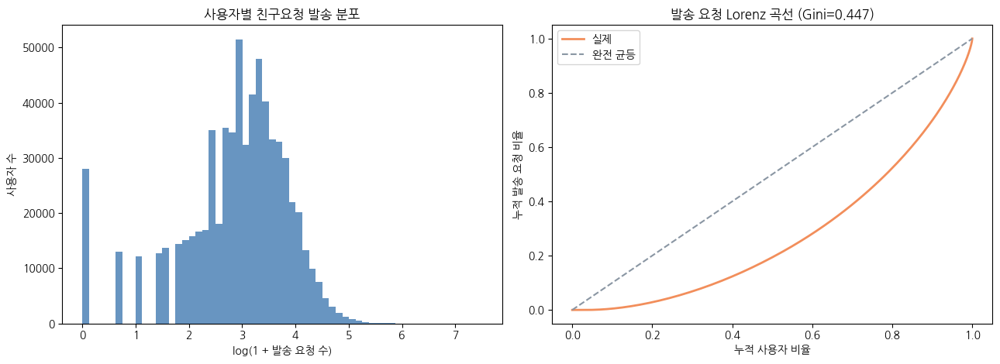

,repeated_directional_pair_flag,directional_pairs,request_records,final_accepted_records,same_school_records,record_share,eventual_acceptance_share
0,0,16965195,16965195.0,12856995.0,13475073.0,0.989387,0.757845
1,1,73039,181980.0,21412.0,144928.0,0.010613,0.117661


In [ ]:
# 요청·친구 수 분포와 반복 요청
user_network = network_con.execute('''
SELECT user_id,
       sent_request_count, received_request_count,
       sent_unique_partner_count, received_unique_partner_count,
       sent_repeated_request_count,
       sent_final_accepted_count, received_final_accepted_count,
       current_friend_list_length,
       TRY_CAST(current_school_id AS BIGINT) AS current_school_id,
       current_school_type
FROM profile
WHERE analysis_eligible_nonstaff_flag = 1
''').fetchdf()

def gini(values):
    x = np.asarray(values, float)
    x = x[np.isfinite(x) & (x >= 0)]
    if len(x) == 0 or x.sum() == 0: return np.nan
    x = np.sort(x)
    n = len(x)
    return (2 * np.sum((np.arange(1, n+1)) * x) / (n*x.sum())) - (n+1)/n

def top_share(values, frac):
    x = np.sort(np.asarray(values, float))[::-1]
    k = max(1, int(np.ceil(len(x)*frac)))
    return x[:k].sum()/x.sum() if x.sum() else np.nan

concentration = []
for col in ["sent_request_count", "received_request_count", "sent_unique_partner_count", "current_friend_list_length"]:
    s = user_network[col].fillna(0)
    concentration.append({
        "metric": col, "mean": s.mean(), "median": s.median(), "p90": s.quantile(.9), "p99": s.quantile(.99),
        "gini": gini(s), "top_1pct_share": top_share(s, .01), "top_10pct_share": top_share(s, .10)
    })
concentration = pd.DataFrame(concentration)
display(concentration.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(np.log1p(user_network.sent_request_count), bins=60, color=COLORS["blue"], alpha=.85)
axes[0].set_xlabel("log(1 + 발송 요청 수)")
axes[0].set_ylabel("사용자 수")
axes[0].set_title("사용자별 친구요청 발송 분포")

x = np.sort(user_network.sent_request_count.fillna(0).to_numpy(float))
lorenz = np.r_[0, np.cumsum(x)/x.sum()]
population = np.linspace(0, 1, len(lorenz))
axes[1].plot(population, lorenz, color=COLORS["orange"], lw=2, label="실제")
axes[1].plot([0,1], [0,1], "--", color=COLORS["gray"], label="완전 균등")
axes[1].set_xlabel("누적 사용자 비율")
axes[1].set_ylabel("누적 발송 요청 비율")
axes[1].set_title(f"발송 요청 Lorenz 곡선 (Gini={gini(x):.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

repeated = network_con.execute('''
SELECT
    repeated_directional_pair_flag,
    COUNT(*) AS directional_pairs,
    SUM(request_record_count) AS request_records,
    SUM(final_accepted_record_count) AS final_accepted_records,
    SUM(CASE WHEN same_school_current_flag = 1 THEN request_record_count ELSE 0 END) AS same_school_records
FROM pair
WHERE analysis_eligible_pair_flag = 1
GROUP BY 1 ORDER BY 1
''').fetchdf()
repeated["record_share"] = repeated.request_records / repeated.request_records.sum()
repeated["eventual_acceptance_share"] = repeated.final_accepted_records / repeated.request_records
display(repeated)

plt.close('all')


- 사용자별 발송 요청 중앙값은 20건이며 상위 10%가 전체 발송량의 30.14%를 차지했다.
- 반복 방향쌍의 요청은 전체의 약 1.06%다. 최종 수락 비중은 약 11.77%로 비반복 방향쌍의 약 75.78%보다 낮았다.


### 3-2-3. 학교 관계와 40명 도달 전후 변화

- 현재 같은 학교인지에 따른 요청 상태와 D0 전후 요청량·참여 범위를 살펴본다.
- 요청 생성일로 기간을 나누고 추출 시점의 최종 수락 여부를 붙인다. D0 전후 차이에는 가입자 구성 변화도 들어 있다.


,school_relation,final_status_code,final_status_label,requests,median_last_update_seconds,p90_last_update_seconds,within_relation_share
0,현재 다른 학교,A,FINAL_ACCEPTED,2498585,26579.0,340066.0,0.7084
1,현재 다른 학교,P,FINAL_PENDING,926078,0.0,0.0,0.2626
2,현재 다른 학교,R,FINAL_REJECTED,102511,50989.0,515031.0,0.0291
3,현재 동일 학교,A,FINAL_ACCEPTED,10379822,18646.0,297070.0,0.7621
4,현재 동일 학교,P,FINAL_PENDING,3012530,0.0,0.0,0.2212
5,현재 동일 학교,R,FINAL_REJECTED,227649,47504.0,577117.6,0.0167


,comparison,chi2,p_value,cramers_v,acceptance_odds_ratio,or_ci_low,or_ci_high,same_school_acceptance_share,cross_school_acceptance_share,risk_difference_pp
0,현재 동일 학교 vs 다른 학교의 최종 수락 상태,53830.089633,0.0,0.056029,1.318769,1.315327,1.32222,0.762101,0.708382,5.371986


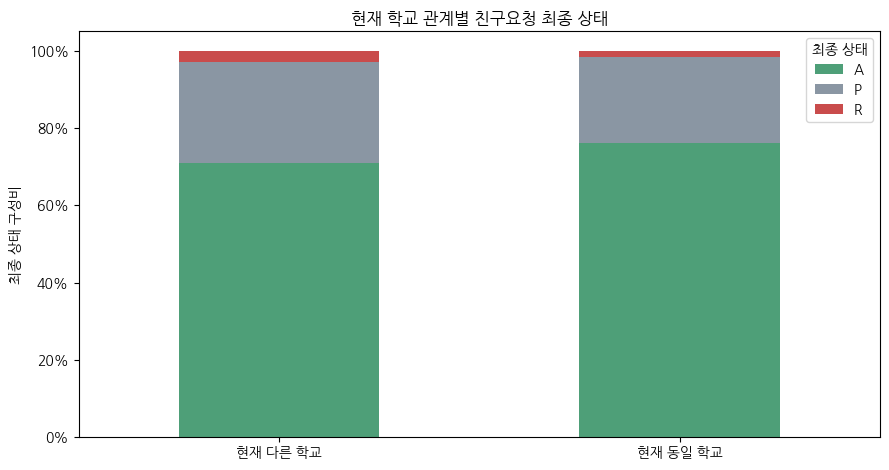

In [ ]:
# 현재 동일 학교 여부별 요청 최종 상태
relation_status = network_con.execute('''
SELECT
    CASE
        WHEN sender_current_school_id IS NULL OR receiver_current_school_id IS NULL THEN '학교관계 미확인'
        WHEN same_school_current_flag = 1 THEN '현재 동일 학교'
        ELSE '현재 다른 학교'
    END AS school_relation,
    final_status_code,
    final_status_label,
    COUNT(*) AS requests,
    MEDIAN(created_to_last_update_seconds) AS median_last_update_seconds,
    QUANTILE_CONT(created_to_last_update_seconds, .9) AS p90_last_update_seconds
FROM event
WHERE analysis_eligible_request_flag = 1
GROUP BY 1,2,3
ORDER BY 1,2
''').fetchdf()
relation_status["within_relation_share"] = relation_status.requests / relation_status.groupby("school_relation").requests.transform("sum")
display(relation_status.round(4))

contingency = relation_status.pivot_table(index="school_relation", columns="final_status_code", values="requests", aggfunc="sum", fill_value=0)
chi2, p, dof, expected = stats.chi2_contingency(contingency)
n = contingency.to_numpy().sum()
cramers_v = math.sqrt(chi2 / (n * min(contingency.shape[0]-1, contingency.shape[1]-1)))

def odds_ratio_ci(a, b, c, d):
    vals = np.array([a,b,c,d], float) + .5
    a,b,c,d = vals
    log_or = np.log(a*d/(b*c))
    se = np.sqrt(1/a+1/b+1/c+1/d)
    return np.exp(log_or), np.exp(log_or-1.96*se), np.exp(log_or+1.96*se)

same = contingency.loc["현재 동일 학교"]
cross = contingency.loc["현재 다른 학교"]
a, b = same.get("A", 0), same.sum()-same.get("A",0)
c, d = cross.get("A", 0), cross.sum()-cross.get("A",0)
or_, lo, hi = odds_ratio_ci(a,b,c,d)
quality_test = pd.DataFrame([{
    "comparison": "현재 동일 학교 vs 다른 학교의 최종 수락 상태",
    "chi2": chi2, "p_value": p, "cramers_v": cramers_v,
    "acceptance_odds_ratio": or_, "or_ci_low": lo, "or_ci_high": hi,
    "same_school_acceptance_share": a/(a+b), "cross_school_acceptance_share": c/(c+d),
    "risk_difference_pp": (a/(a+b)-c/(c+d))*100
}])
display(quality_test)

plot_status = relation_status.pivot_table(index="school_relation", columns="final_status_code", values="within_relation_share", fill_value=0)
plot_status[[c for c in ["A","P","R"] if c in plot_status]].plot(kind="bar", stacked=True, figsize=(9,4.8), color=[COLORS["green"], COLORS["gray"], COLORS["red"]])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.ylabel("최종 상태 구성비")
plt.xlabel("")
plt.xticks(rotation=0)
plt.title("현재 학교 관계별 친구요청 최종 상태")
plt.legend(title="최종 상태")
plt.tight_layout()
plt.show()

plt.close('all')


- 같은 학교 요청의 최종 수락 비중은 76.21%, 다른 학교는 70.84%로 약 5.37%p 차이다.
- 같은 학교에서 더 높지만 효과 크기 Cramér's V는 약 0.056으로 작다.


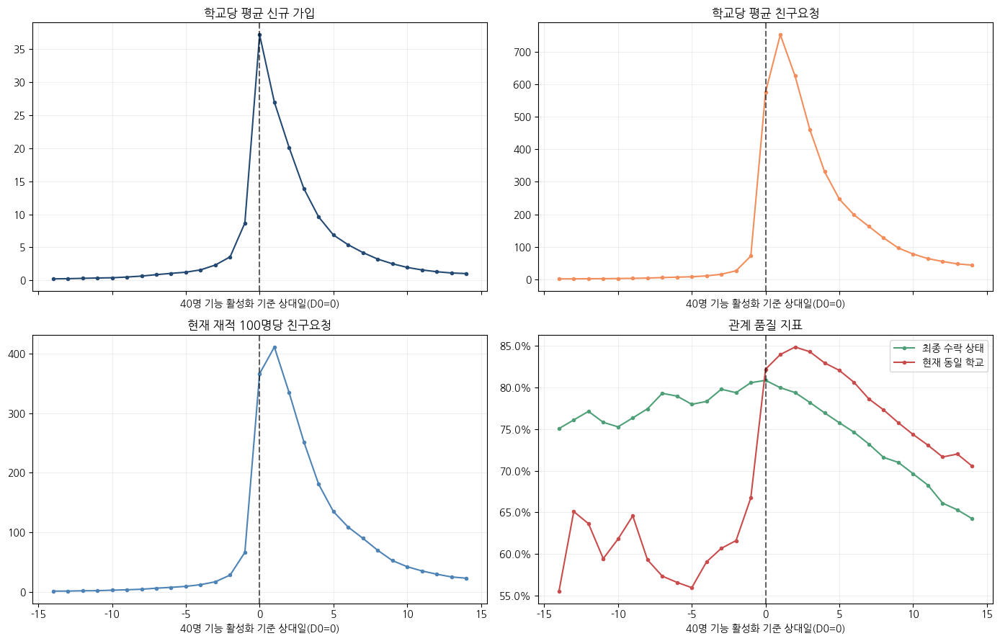

완전 관측 학교 수: 3,792개


In [ ]:
# 40명 도달 전후 학교별 관계 행동 곡선
event_bounds = network_con.execute("SELECT MIN(CAST(request_created_at_raw AS DATE)), MAX(CAST(request_created_at_raw AS DATE)) FROM event WHERE analysis_eligible_request_flag=1").fetchone()
min_event_date, max_event_date = pd.Timestamp(event_bounds[0]), pd.Timestamp(event_bounds[1])

school_event = network_con.execute(f'''
WITH base AS (
    SELECT
        school_id,
        CAST(activity_date AS DATE) AS activity_date,
        CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE) AS d0_date,
        DATE_DIFF('day', CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE), CAST(activity_date AS DATE)) AS rel_day,
        current_roster_nonstaff_account_count AS roster_size,
        new_nonstaff_account_count_current_roster AS new_users,
        sent_request_created_count AS sent_requests,
        sent_request_user_count AS sender_days,
        sent_created_final_accepted_count AS eventual_accepted,
        sent_created_final_pending_count AS eventual_pending,
        sent_created_final_rejected_count AS eventual_rejected,
        sent_within_school_count_current AS same_school_requests,
        sent_cross_school_count_current AS cross_school_requests
    FROM school_daily
    WHERE current_roster_reached_40_flag = 1
      AND TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) IS NOT NULL
)
SELECT * FROM base
WHERE rel_day BETWEEN -14 AND 14
  AND d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                  AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
ORDER BY school_id, rel_day
''').fetchdf()
school_event["activity_date"] = pd.to_datetime(school_event.activity_date)
school_event["d0_date"] = pd.to_datetime(school_event.d0_date)
school_event["requests_per_100_roster"] = 100 * school_event.sent_requests / school_event.roster_size.replace(0, np.nan)
school_event["sender_days_per_100_roster"] = 100 * school_event.sender_days / school_event.roster_size.replace(0, np.nan)
school_event["new_users_per_100_roster"] = 100 * school_event.new_users / school_event.roster_size.replace(0, np.nan)
school_event["same_school_share"] = school_event.same_school_requests / school_event.sent_requests.replace(0, np.nan)
school_event["eventual_acceptance_share"] = school_event.eventual_accepted / school_event.sent_requests.replace(0, np.nan)

event_curve = school_event.groupby("rel_day").agg(
    schools=("school_id","nunique"),
    mean_new_users=("new_users","mean"), median_new_users=("new_users","median"),
    mean_requests=("sent_requests","mean"), median_requests=("sent_requests","median"),
    mean_request_rate=("requests_per_100_roster","mean"), median_request_rate=("requests_per_100_roster","median"),
    mean_sender_day_rate=("sender_days_per_100_roster","mean"),
    pooled_same_school_requests=("same_school_requests","sum"), pooled_requests=("sent_requests","sum"),
    pooled_eventual_accepted=("eventual_accepted","sum")
).reset_index()
event_curve["pooled_same_school_share"] = event_curve.pooled_same_school_requests/event_curve.pooled_requests
event_curve["pooled_eventual_acceptance_share"] = event_curve.pooled_eventual_accepted/event_curve.pooled_requests

fig, axes = plt.subplots(2,2, figsize=(14,9), sharex=True)
axes[0,0].plot(event_curve.rel_day, event_curve.mean_new_users, marker="o", ms=3, color=COLORS["navy"])
axes[0,0].set_title("학교당 평균 신규 가입")
axes[0,1].plot(event_curve.rel_day, event_curve.mean_requests, marker="o", ms=3, color=COLORS["orange"])
axes[0,1].set_title("학교당 평균 친구요청")
axes[1,0].plot(event_curve.rel_day, event_curve.mean_request_rate, marker="o", ms=3, color=COLORS["blue"])
axes[1,0].set_title("현재 재적 100명당 친구요청")
axes[1,1].plot(event_curve.rel_day, event_curve.pooled_eventual_acceptance_share, marker="o", ms=3, color=COLORS["green"], label="최종 수락 상태")
axes[1,1].plot(event_curve.rel_day, event_curve.pooled_same_school_share, marker="o", ms=3, color=COLORS["red"], label="현재 동일 학교")
axes[1,1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1,1].set_title("관계 품질 지표")
axes[1,1].legend()
for ax in axes.flat:
    ax.axvline(0, ls="--", color="black", alpha=.6)
    ax.grid(alpha=.2)
    ax.set_xlabel("40명 기능 활성화 기준 상대일(D0=0)")
plt.tight_layout()
plt.show()
print(f"완전 관측 학교 수: {school_event.school_id.nunique():,}개")

plt.close('all')


- D-14~D+14가 모두 관측되는 3,792개 학교를 사용했다. 요청량과 발송 사용자·일은 현재 재적 인원으로도 나눠 학교 규모 차이를 반영한다.


In [ ]:
# 학교 내 전후 대응 비교·차이 신뢰구간
def label_window(day):
    if -14 <= day <= -8: return "baseline"
    if -7 <= day <= -1: return "pre"
    if 1 <= day <= 7: return "early"
    if 8 <= day <= 14: return "late"
    return None

school_event["window"] = school_event.rel_day.map(label_window)
window_long = school_event.dropna(subset=["window"]).groupby(["school_id","d0_date","window"]).agg(
    roster_size=("roster_size","max"),
    new_users=("new_users","sum"),
    sent_requests=("sent_requests","sum"),
    sender_days=("sender_days","sum"),
    eventual_accepted=("eventual_accepted","sum"),
    eventual_pending=("eventual_pending","sum"),
    eventual_rejected=("eventual_rejected","sum"),
    same_school_requests=("same_school_requests","sum"),
    active_request_days=("sent_requests", lambda s: int((s>0).sum()))
).reset_index()
window_long["requests_per_100_roster"] = 100*window_long.sent_requests/window_long.roster_size.replace(0,np.nan)
window_long["sender_days_per_100_roster"] = 100*window_long.sender_days/window_long.roster_size.replace(0,np.nan)
window_long["new_users_per_100_roster"] = 100*window_long.new_users/window_long.roster_size.replace(0,np.nan)
window_long["eventual_acceptance_share"] = window_long.eventual_accepted/window_long.sent_requests.replace(0,np.nan)
window_long["same_school_share"] = window_long.same_school_requests/window_long.sent_requests.replace(0,np.nan)

wide = window_long.pivot(index=["school_id","d0_date"], columns="window")
wide.columns = [f"{metric}_{window}" for metric,window in wide.columns]
wide = wide.reset_index()

rng = np.random.default_rng(20260911)
def paired_test(metric, w1, w2, boot_n=2000):
    a = wide[f"{metric}_{w1}"]
    b = wide[f"{metric}_{w2}"]
    valid = a.notna() & b.notna()
    a, b = a[valid].to_numpy(float), b[valid].to_numpy(float)
    diff = b-a
    nonzero = diff[diff!=0]
    if len(nonzero):
        stat, p = stats.wilcoxon(nonzero, alternative="two-sided", zero_method="wilcox")
        pos, neg = np.sum(nonzero>0), np.sum(nonzero<0)
        sign_effect = (pos-neg)/len(nonzero)
    else:
        stat, p, sign_effect = np.nan, np.nan, np.nan
    idx = rng.integers(0, len(diff), size=(boot_n, len(diff)))
    med_boot = np.median(diff[idx], axis=1)
    lo, hi = np.quantile(med_boot, [.025,.975])
    return {"metric":metric,"comparison":f"{w1}→{w2}","schools":len(diff),
            "mean_before":np.mean(a),"mean_after":np.mean(b),"mean_difference":np.mean(diff),
            "median_before":np.median(a),"median_after":np.median(b),"median_difference":np.median(diff),
            "median_diff_ci_low":lo,"median_diff_ci_high":hi,
            "wilcoxon_stat":stat,"p_value":p,"paired_sign_effect":sign_effect,
            "share_increased":np.mean(diff>0)}

metrics = ["new_users_per_100_roster","requests_per_100_roster","sender_days_per_100_roster",
           "active_request_days","eventual_acceptance_share","same_school_share"]
test_rows=[]
for metric in metrics:
    test_rows.append(paired_test(metric,"pre","early"))
    test_rows.append(paired_test(metric,"early","late"))
paired_tests = pd.DataFrame(test_rows)
display(paired_tests.round(4))


,metric,comparison,schools,mean_before,mean_after,mean_difference,median_before,median_after,median_difference,median_diff_ci_low,median_diff_ci_high,wilcoxon_stat,p_value,paired_sign_effect,share_increased
0,new_users_per_100_roster,pre→early,3792,16.0708,46.0124,29.9416,12.2951,48.3516,35.7143,34.8485,36.9428,605643.5,0.0,0.6919,0.8383
1,new_users_per_100_roster,early→late,3792,46.0124,6.9146,-39.0978,48.3516,4.8000,-40.8526,-41.5909,-40.1303,48146.0,0.0,-0.9388,0.0303
2,requests_per_100_roster,pre→early,3792,147.6547,1511.2671,1363.6124,59.2243,1493.0024,1393.4279,1365.6056,1429.3880,99953.5,0.0,0.8775,0.9380
3,requests_per_100_roster,early→late,3792,1511.2671,278.5812,-1232.6859,1493.0024,207.7182,-1221.0817,-1260.5899,-1191.5026,97687.0,0.0,-0.9107,0.0446
4,sender_days_per_100_roster,pre→early,3792,18.8031,148.9272,130.1242,11.1111,156.9482,143.2836,141.3793,145.0992,57682.5,0.0,0.9059,0.9504
5,sender_days_per_100_roster,early→late,3792,148.9272,42.3413,-106.5859,156.9482,36.1238,-115.9897,-118.1818,-113.9301,98017.5,0.0,-0.9096,0.0451
6,active_request_days,pre→early,3792,3.3972,6.8534,3.4562,3.0000,7.0000,4.0000,4.0000,4.0000,81692.5,0.0,0.9345,0.8805
7,active_request_days,early→late,3792,6.8534,6.3972,-0.4562,7.0000,7.0000,0.0000,0.0000,0.0000,31753.0,0.0,-0.8193,0.0227
8,eventual_acceptance_share,pre→early,3485,0.8206,0.7446,-0.0760,0.8357,0.7660,-0.0795,-0.0840,-0.0752,833777.0,0.0,-0.6109,0.1945
9,eventual_acceptance_share,early→late,3767,0.7470,0.6087,-0.1383,0.7661,0.6321,-0.1269,-0.1304,-0.1233,122403.5,0.0,-0.9172,0.0414


- 재적 100명당 요청량의 학교 중앙값은 직전 주 59.22건 → 첫째 주 1,493.00건 → 둘째 주 207.72건이다.
- 요청이 발생한 날의 중앙값은 첫째 주·둘째 주 모두 7일이다. 활동은 남아 있지만 요청 규모가 크게 줄었다.


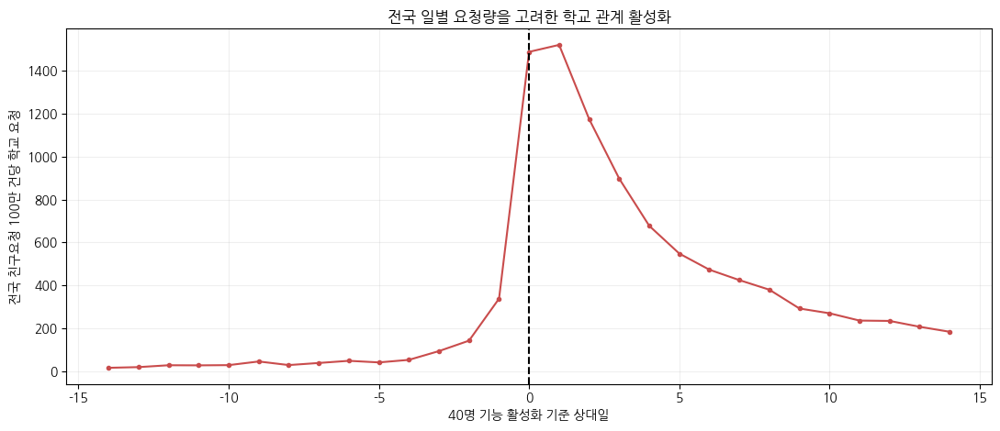

,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,pre→early,3792,23.437997,552.600156,504.329517,0.938819,0.0
1,early→late,3792,552.600156,128.461497,-363.706373,0.088344,0.0


In [ ]:
# 전국 일별 요청량 대비 학교 요청 변화
national = daily.set_index("activity_date")["sent_requests"]
school_event["national_requests"] = school_event.activity_date.map(national)
school_event["request_share_per_million"] = 1_000_000 * school_event.sent_requests / school_event.national_requests.replace(0,np.nan)
adjusted_curve = school_event.groupby("rel_day").agg(
    mean_share_per_million=("request_share_per_million","mean"),
    median_share_per_million=("request_share_per_million","median"),
    mean_requests_per_100=("requests_per_100_roster","mean")
).reset_index()

fig, ax = plt.subplots(figsize=(11,4.8))
ax.plot(adjusted_curve.rel_day, adjusted_curve.mean_share_per_million, marker="o", ms=3, color=COLORS["red"])
ax.axvline(0, ls="--", color="black")
ax.set_xlabel("40명 기능 활성화 기준 상대일")
ax.set_ylabel("전국 친구요청 100만 건당 학교 요청")
ax.set_title("전국 일별 요청량을 고려한 학교 관계 활성화")
ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

adj_window = school_event.dropna(subset=["window"]).groupby(["school_id","window"]).request_share_per_million.mean().unstack()
adj_rows=[]
for w1,w2 in [("pre","early"),("early","late")]:
    a,b=adj_window[w1],adj_window[w2]
    valid=a.notna()&b.notna(); diff=(b[valid]-a[valid]).to_numpy()
    nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    adj_rows.append({"comparison":f"{w1}→{w2}","schools":len(diff),"median_before":np.median(a[valid]),
                     "median_after":np.median(b[valid]),"median_difference":np.median(diff),
                     "share_increased":np.mean(diff>0),"wilcoxon_p":p})
adjusted_tests=pd.DataFrame(adj_rows)
display(adjusted_tests)

plt.close('all')


- 전국 요청 100만 건당 학교 요청량 중앙값도 23.44 → 552.60 → 128.46으로 움직였다.
- 전국 요청량의 변화를 반영해도 D0 주변 증가와 둘째 주 감소가 남는다. 인과효과를 추정하려면 별도 대조군이 필요하다.


final_status_code,A,P,R
window,,,
pre,427335,99854,7866
early,8227610,2116788,197455
late,1332719,544577,54642


,test,chi2,p_value,cramers_v,early_acceptance_share,late_acceptance_share,early_vs_late_acceptance_or,or_ci_low,or_ci_high,risk_difference_pp
0,D0 window × final status,78698.475509,0.0,0.054998,0.780471,0.689835,1.598497,1.593104,1.603908,9.063566


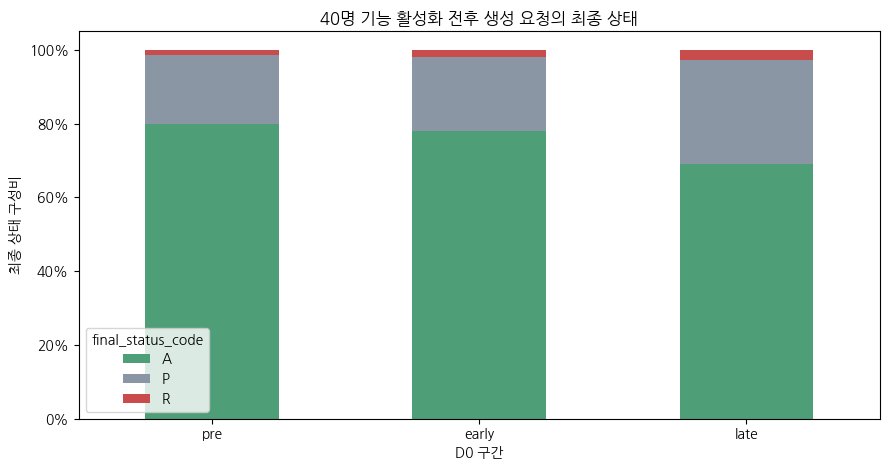

In [ ]:
# D0 구간별 요청 최종 상태 구성
phase_quality = network_con.execute(f'''
WITH d0 AS (
    SELECT school_id,
           CAST(MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS DATE) AS d0_date
    FROM school_daily
    WHERE current_roster_reached_40_flag=1
    GROUP BY 1
), joined AS (
    SELECT e.final_status_code,
           e.same_school_current_flag,
           e.created_to_last_update_seconds,
           DATE_DIFF('day', d.d0_date, CAST(e.request_created_at_raw AS DATE)) AS rel_day
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
)
SELECT CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
            WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
            WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS window,
       final_status_code,
       same_school_current_flag,
       COUNT(*) AS requests,
       MEDIAN(created_to_last_update_seconds) AS median_last_update_seconds,
       QUANTILE_CONT(created_to_last_update_seconds,.9) AS p90_last_update_seconds
FROM joined
WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
GROUP BY 1,2,3
ORDER BY 1,2,3
''').fetchdf()

status_tab=phase_quality.groupby(["window","final_status_code"]).requests.sum().unstack(fill_value=0).reindex(["pre","early","late"])
chi2,p,dof,expected=stats.chi2_contingency(status_tab)
n=status_tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(status_tab.shape[0]-1,status_tab.shape[1]-1)))

def window_acceptance(window):
    row=status_tab.loc[window]
    return row.get("A",0), row.sum()-row.get("A",0)
ea,en=window_acceptance("early"); la,ln=window_acceptance("late")
or_el,lo_el,hi_el=odds_ratio_ci(ea,en,la,ln)
phase_tests=pd.DataFrame([{
    "test":"D0 window × final status", "chi2":chi2,"p_value":p,"cramers_v":cv,
    "early_acceptance_share":ea/(ea+en),"late_acceptance_share":la/(la+ln),
    "early_vs_late_acceptance_or":or_el,"or_ci_low":lo_el,"or_ci_high":hi_el,
    "risk_difference_pp":100*(ea/(ea+en)-la/(la+ln))
}])
display(status_tab)
display(phase_tests)

comp=(status_tab.T/status_tab.sum(axis=1)).T
comp.plot(kind="bar",stacked=True,figsize=(9,4.8),color=[COLORS["green"],COLORS["gray"],COLORS["red"]])
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.xticks(rotation=0)
plt.xlabel("D0 구간")
plt.ylabel("최종 상태 구성비")
plt.title("40명 기능 활성화 전후 생성 요청의 최종 상태")
plt.tight_layout()
plt.show()

plt.close('all')


- 최종 수락 비중은 첫째 주 78.05%에서 둘째 주 68.98%로 약 9.06%p 낮아졌다.
- 해당 구간에 생성된 요청을 모두 합친 건수 기준 비중이다. 요청량이 많은 학교의 영향이 더 크게 반영된다.


### 3-2-4. 후기 활동과 연결되는 관계 지표

- 첫째 주 관계 지표와 둘째 주 요청량의 연관성을 살펴본다.
- 현재 친구 수·누적 요청의 차이와 초대 지표의 계산 가능 범위도 정리한다.


,feature,spearman_rho_with_late_request_rate,p_value
5,early_acceptance_share,0.373350,1.815796e-125
0,log_roster_size,0.326872,6.309965e-95
2,early_new_users_per_100,0.200752,1.058409e-35
6,early_same_school_share,0.172126,1.493691e-26
7,early_active_days,0.164341,2.558237e-24
4,early_sender_days_per_100,0.063071,1.034416e-04
3,early_requests_per_100,0.054609,7.777368e-04
1,d0_day_index,-0.152852,3.227670e-21


,feature,standardized_coef,hc3_se,z,p_value,ci_low,ci_high
0,intercept,5.2041,0.0144,362.4930,0.0000,5.1760,5.2322
1,log_roster_size,0.0487,0.0285,1.7076,0.0877,-0.0072,0.1046
2,d0_day_index,-0.1778,0.0310,-5.7389,0.0000,-0.2386,-0.1171
3,early_new_users_per_100,0.1136,0.0300,3.7921,0.0001,0.0549,0.1724
4,early_requests_per_100,0.0532,0.0341,1.5570,0.1195,-0.0138,0.1201
5,early_sender_days_per_100,-0.4031,0.0413,-9.7550,0.0000,-0.4841,-0.3221
6,early_acceptance_share,0.5389,0.0301,17.9172,0.0000,0.4800,0.5979
7,early_same_school_share,0.1060,0.0206,5.1407,0.0000,0.0656,0.1465
8,early_active_days,0.1241,0.0347,3.5789,0.0003,0.0561,0.1920


,train_schools,test_schools,temporal_cutoff,test_r2,test_mae_log_scale,selected_alpha,random_5fold_r2_mean,random_5fold_r2_sd
0,3110,674,2023-05-21,-0.961369,1.417788,5.623413,0.328563,0.033038


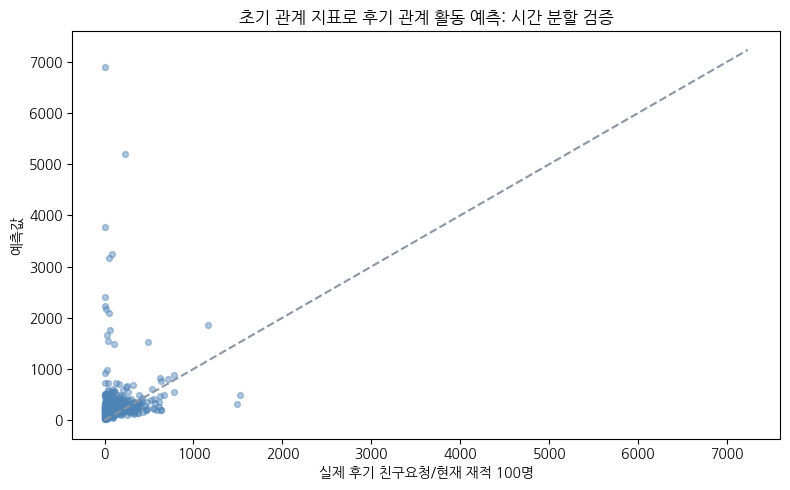

In [ ]:
# 초기 관계 지표·후기 요청량 회귀와 시간 검증
model_df = pd.DataFrame({
    "school_id": wide.school_id,
    "d0_date": pd.to_datetime(wide.d0_date),
    "roster_size": wide.get("roster_size_early"),
    "early_new_users_per_100": wide.get("new_users_per_100_roster_early"),
    "early_requests_per_100": wide.get("requests_per_100_roster_early"),
    "early_sender_days_per_100": wide.get("sender_days_per_100_roster_early"),
    "early_acceptance_share": wide.get("eventual_acceptance_share_early"),
    "early_same_school_share": wide.get("same_school_share_early"),
    "early_active_days": wide.get("active_request_days_early"),
    "late_requests_per_100": wide.get("requests_per_100_roster_late"),
    "late_active_days": wide.get("active_request_days_late"),
}).replace([np.inf,-np.inf],np.nan)
model_df["d0_day_index"]=(model_df.d0_date-model_df.d0_date.min()).dt.days
model_df["log_roster_size"]=np.log1p(model_df.roster_size)
model_df["log_late_request_rate"]=np.log1p(model_df.late_requests_per_100)
features=["log_roster_size","d0_day_index","early_new_users_per_100","early_requests_per_100",
          "early_sender_days_per_100","early_acceptance_share","early_same_school_share","early_active_days"]
m=model_df.dropna(subset=features+["log_late_request_rate"]).copy()

corr_rows=[]
for x in features:
    rho,p=stats.spearmanr(m[x],m.log_late_request_rate)
    corr_rows.append({"feature":x,"spearman_rho_with_late_request_rate":rho,"p_value":p})
corr=pd.DataFrame(corr_rows).sort_values("spearman_rho_with_late_request_rate",ascending=False)

X0=m[features].to_numpy(float)
means=X0.mean(axis=0); stds=X0.std(axis=0,ddof=0); stds[stds==0]=1
Z=(X0-means)/stds
X=np.c_[np.ones(len(Z)),Z]
y=m.log_late_request_rate.to_numpy(float)
xtx_inv=np.linalg.pinv(X.T@X)
beta=xtx_inv@X.T@y
resid=y-X@beta
hat=np.sum((X@xtx_inv)*X,axis=1)
adj=(resid/(1-hat))**2
meat=X.T@(X*adj[:,None])
vcov=xtx_inv@meat@xtx_inv
se=np.sqrt(np.diag(vcov)); z=beta/se; pvals=2*stats.norm.sf(np.abs(z))
names=["intercept"]+features
ols=pd.DataFrame({"feature":names,"standardized_coef":beta,"hc3_se":se,"z":z,"p_value":pvals,
                  "ci_low":beta-1.96*se,"ci_high":beta+1.96*se})

cutoff=m.d0_date.quantile(.8)
train=m.d0_date<=cutoff; test=~train
ridge=make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-3,3,25)))
ridge.fit(m.loc[train,features],m.loc[train,"log_late_request_rate"])
pred=ridge.predict(m.loc[test,features])
random_cv=KFold(n_splits=5,shuffle=True,random_state=20260911)
random_cv_r2=cross_val_score(
    make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-3,3,25))),
    m[features],m["log_late_request_rate"],cv=random_cv,scoring="r2"
)
model_quality=pd.DataFrame([{
    "train_schools":int(train.sum()),"test_schools":int(test.sum()),"temporal_cutoff":cutoff,
    "test_r2":r2_score(m.loc[test,"log_late_request_rate"],pred),
    "test_mae_log_scale":mean_absolute_error(m.loc[test,"log_late_request_rate"],pred),
    "selected_alpha":ridge.named_steps["ridgecv"].alpha_,
    "random_5fold_r2_mean":random_cv_r2.mean(),
    "random_5fold_r2_sd":random_cv_r2.std()
}])
display(corr)
display(ols.round(4))
display(model_quality)

fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(np.expm1(m.loc[test,"log_late_request_rate"]),np.expm1(pred),s=18,alpha=.45,color=COLORS["blue"])
mx=max(ax.get_xlim()[1],ax.get_ylim()[1]); ax.plot([0,mx],[0,mx],"--",color=COLORS["gray"])
ax.set_xlabel("실제 후기 친구요청/현재 재적 100명")
ax.set_ylabel("예측값")
ax.set_title("초기 관계 지표로 후기 관계 활동 예측: 시간 분할 검증")
plt.tight_layout()
plt.show()

plt.close('all')


- 초기 최종 수락 비중과 후기 요청량의 순위상관은 0.373으로, 초기 요청량 자체의 0.055보다 높았다.
- 무작위 교차검증 R²는 약 0.329지만 나중에 도달한 학교에서는 -0.961이다. 시기가 달라지자 예측력이 떨어졌다.
- 최종 수락 상태가 D+7에 확정됐는지도 알 수 없어 실제 예측에 쓰기에는 제약이 있다.


,metric,spearman_rho
3,received_unique_partner_count,0.765397
1,received_request_count,0.764504
4,sent_final_accepted_count,0.705506
2,sent_unique_partner_count,0.683603
0,sent_request_count,0.683041
5,received_final_accepted_count,0.675047


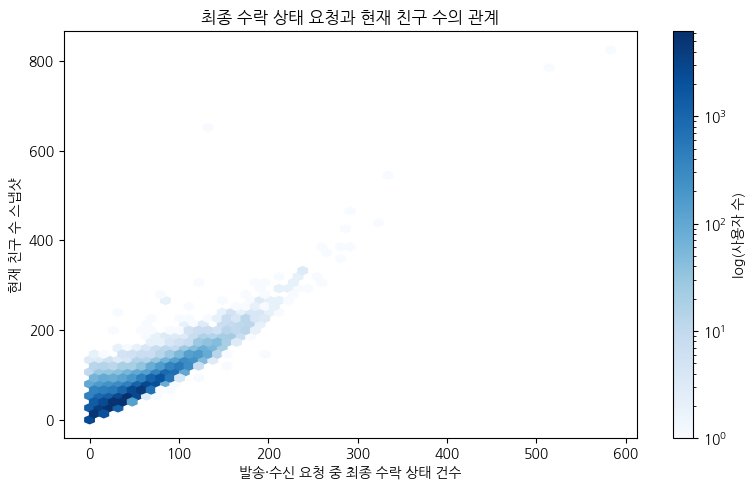

In [ ]:
# 현재 친구 수와 누적 요청 지표 관계
snapshot_cols=["sent_request_count","received_request_count","sent_unique_partner_count","received_unique_partner_count",
               "sent_final_accepted_count","received_final_accepted_count","current_friend_list_length"]
snapshot_corr=user_network[snapshot_cols].corr(method="spearman")[["current_friend_list_length"]].drop("current_friend_list_length")
snapshot_corr=snapshot_corr.reset_index().rename(columns={"index":"metric","current_friend_list_length":"spearman_rho"})
display(snapshot_corr.sort_values("spearman_rho",ascending=False))

sample=user_network.sample(min(80000,len(user_network)),random_state=20260911)
plt.figure(figsize=(8,5))
plt.hexbin(sample.sent_final_accepted_count+sample.received_final_accepted_count,
           sample.current_friend_list_length,gridsize=55,bins="log",mincnt=1,cmap="Blues")
plt.xlabel("발송·수신 요청 중 최종 수락 상태 건수")
plt.ylabel("현재 친구 수 스냅샷")
plt.title("최종 수락 상태 요청과 현재 친구 수의 관계")
plt.colorbar(label="log(사용자 수)")
plt.tight_layout()
plt.show()

plt.close('all')


- 현재 친구 수와 수신한 고유 상대 수의 순위상관은 0.765이며, 누적 수신 요청 수도 비슷한 수준이다.
- 요청에는 반복 상대와 과거 관계가 포함될 수 있어 누적 수락 건수와 현재 친구 수는 따로 쓴다.


In [ ]:
# 연락처 관측 범위·초대 지표 계산 가능성
contact_audit=network_con.execute('''
SELECT
    COUNT(*) AS all_users,
    SUM(contacts_observed_flag) AS users_with_contact_snapshot,
    SUM(CASE WHEN TRY_CAST(invite_user_id_list_length AS BIGINT)>0 THEN 1 ELSE 0 END) AS users_with_inviter_reference,
    SUM(CASE WHEN TRY_CAST(contacts_count_source AS BIGINT)>0 THEN 1 ELSE 0 END) AS users_with_contacts,
    SUM(analysis_eligible_nonstaff_flag) AS eligible_users
FROM acquisition
''').fetchdf()
contact_audit["contact_snapshot_coverage"] = contact_audit.users_with_contact_snapshot/contact_audit.all_users
contact_audit["inviter_reference_coverage"] = contact_audit.users_with_inviter_reference/contact_audit.all_users
display(contact_audit.round(4))

identifiability=pd.DataFrame([
    ["초대 발송자","연락처 스냅샷 일부만 관측","전체 K 계산 불가"],
    ["초대 수신자","가입자와 직접 연결되는 초대 수신 이벤트 없음","가입 전환율 계산 불가"],
    ["초대 발송 시각","없음","Viral Cycle Time 계산 불가"],
    ["초대를 통한 가입 시각","없음","Viral Cycle Time 계산 불가"],
    ["친구요청 발송·수신 시각","있음","가입 후 Network 활성화 분석 가능"],
],columns=["필요 정보","현재 관측 상태","판단"])
display(identifiability)


,all_users,users_with_contact_snapshot,users_with_inviter_reference,users_with_contacts,eligible_users,contact_snapshot_coverage,inviter_reference_coverage
0,677085,5063.0,1158.0,5060.0,677081.0,0.0075,0.0017


,필요 정보,현재 관측 상태,판단
0,초대 발송자,연락처 스냅샷 일부만 관측,전체 K 계산 불가
1,초대 수신자,가입자와 직접 연결되는 초대 수신 이벤트 없음,가입 전환율 계산 불가
2,초대 발송 시각,없음,Viral Cycle Time 계산 불가
3,초대를 통한 가입 시각,없음,Viral Cycle Time 계산 불가
4,친구요청 발송·수신 시각,있음,가입 후 Network 활성화 분석 가능


- 연락처 스냅샷은 5,063명(전체의 약 0.75%)에게 있으며, 이 중 초대자 참조가 있는 사용자는 1,158명이다.
- 초대 발송 시각과 초대 후 가입 연결이 없어 K-Factor·Viral Cycle Time은 계산할 수 없다.


### 3-2-5. 초기 요청 증가와 둘째 주 지속

- 요청량을 참여한 사용자·일 수와 사용자·일당 발송량으로 나눈다. 같은 사람이 여러 날 보내면 사용자·일에도 여러 번 집계된다.
- 요청 중 신규 가입자의 첫날 행동 비중과 가입 후 둘째 주 발송 여부를 살펴본다.


,window,schools,median_requests_per_100,median_sender_days_per_100,median_requests_per_sender_day,median_active_days
0,baseline,3792,0.0000,0.0000,3.0000,0.0
1,pre,3792,59.2243,11.1111,5.4286,3.0
2,early,3792,1493.0024,156.9482,9.5992,7.0
3,late,3792,207.7182,36.1238,5.8381,7.0


,metric,comparison,schools,median_before,median_after,median_difference,median_diff_ci_low,median_diff_ci_high,share_increased,wilcoxon_p
0,sender_days_per_100_roster,pre→early,3792,11.1111,156.9482,143.2836,141.4522,145.0620,0.9504,0.0
1,sender_days_per_100_roster,early→late,3792,156.9482,36.1238,-115.9897,-118.2482,-114.0109,0.0451,0.0
2,requests_per_sender_day,pre→early,3485,5.4286,9.4667,3.8304,3.6513,4.0131,0.8000,0.0
3,requests_per_sender_day,early→late,3767,9.6036,5.8372,-3.8125,-3.9067,-3.6778,0.1149,0.0
4,active_request_days,pre→early,3792,3.0000,7.0000,4.0000,4.0000,4.0000,0.8805,0.0
5,active_request_days,early→late,3792,7.0000,7.0000,0.0000,0.0000,0.0000,0.0227,0.0


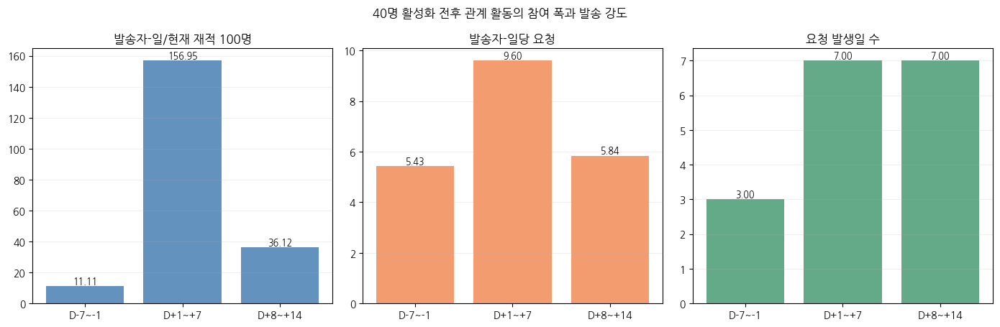

In [ ]:
# 요청량을 참여 범위와 발송 강도로 분해
decomp = window_long.copy()
decomp["requests_per_sender_day"] = decomp.sent_requests / decomp.sender_days.replace(0, np.nan)
decomp_summary = (decomp.groupby("window")
                  .agg(schools=("school_id","nunique"),
                       median_requests_per_100=("requests_per_100_roster","median"),
                       median_sender_days_per_100=("sender_days_per_100_roster","median"),
                       median_requests_per_sender_day=("requests_per_sender_day","median"),
                       median_active_days=("active_request_days","median"))
                  .reindex(["baseline","pre","early","late"]).reset_index())

decomp_wide = decomp.pivot(index=["school_id","d0_date"], columns="window")
decomp_wide.columns = [f"{metric}_{window}" for metric,window in decomp_wide.columns]
decomp_wide = decomp_wide.reset_index()

def paired_from_frame(frame, metric, w1, w2, boot_n=2000):
    a=frame[f"{metric}_{w1}"]; b=frame[f"{metric}_{w2}"]
    valid=a.notna()&b.notna(); a=a[valid].to_numpy(float); b=b[valid].to_numpy(float)
    diff=b-a; nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    boots=[]
    for _ in range(boot_n):
        boots.append(np.median(rng.choice(diff,size=len(diff),replace=True)))
    return {"metric":metric,"comparison":f"{w1}→{w2}","schools":len(diff),
            "median_before":np.median(a),"median_after":np.median(b),
            "median_difference":np.median(diff),"median_diff_ci_low":np.quantile(boots,.025),
            "median_diff_ci_high":np.quantile(boots,.975),"share_increased":np.mean(diff>0),
            "wilcoxon_p":p}

decomp_test_rows=[]
for metric in ["sender_days_per_100_roster","requests_per_sender_day","active_request_days"]:
    decomp_test_rows.append(paired_from_frame(decomp_wide,metric,"pre","early"))
    decomp_test_rows.append(paired_from_frame(decomp_wide,metric,"early","late"))
decomp_tests=pd.DataFrame(decomp_test_rows)
display(decomp_summary.round(4))
display(decomp_tests.round(4))

fig,axes=plt.subplots(1,3,figsize=(14,4.6))
order=["pre","early","late"]
labels=["D-7~-1","D+1~+7","D+8~+14"]
specs=[("median_sender_days_per_100","발송자-일/현재 재적 100명",COLORS["blue"]),
       ("median_requests_per_sender_day","발송자-일당 요청",COLORS["orange"]),
       ("median_active_days","요청 발생일 수",COLORS["green"])]
temp=decomp_summary.set_index("window")
for ax,(col,title,color) in zip(axes,specs):
    vals=temp.loc[order,col]
    ax.bar(labels,vals,color=color,alpha=.88)
    for i,v in enumerate(vals): ax.text(i,v,f"{v:.2f}",ha="center",va="bottom",fontsize=9)
    ax.set_title(title); ax.grid(axis="y",alpha=.2)
plt.suptitle("40명 활성화 전후 관계 활동의 참여 폭과 발송 강도")
plt.tight_layout()
plt.show()

plt.close('all')


- 재적 100명당 발송 사용자·일의 학교 중앙값은 직전 주 11.11 → 첫째 주 156.95 → 둘째 주 36.12다.
- 발송 사용자·일당 요청 수도 첫째 주 약 9.60건에서 둘째 주 약 5.84건으로 줄었다. 참여 범위와 발송 강도 모두 낮아졌다.


,phase,sender_age_band,requests,senders,eventual_accepted,same_school_requests,phase_request_share,eventual_acceptance_share,same_school_share
0,early,가입 1~3일,1742843,226831,1291139.0,1369197.0,0.1653,0.7408,0.7856
1,early,가입 24시간 이내,7360591,361829,5930167.0,6392329.0,0.6982,0.8057,0.8685
2,early,가입 31일+,2252,306,1434.0,1658.0,0.0002,0.6368,0.7362
3,early,가입 4~7일,1115129,166668,784804.0,813539.0,0.1058,0.7038,0.7295
4,early,가입 8~30일,321038,38056,220066.0,214237.0,0.0305,0.6855,0.6673
5,late,가입 1~3일,125675,23375,89345.0,94464.0,0.0651,0.7109,0.7517
6,late,가입 24시간 이내,1075560,47837,784672.0,862695.0,0.5567,0.7295,0.8021
7,late,가입 31일+,1628,318,799.0,938.0,0.0008,0.4908,0.5762
8,late,가입 4~7일,237133,53368,158933.0,163851.0,0.1227,0.6702,0.6910
9,late,가입 8~30일,491942,105816,298970.0,314956.0,0.2546,0.6077,0.6402


,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,pre→early,3485,0.9374,0.6794,-0.2508,0.1116,0.0
1,early→late,3767,0.6809,0.5073,-0.1696,0.1925,0.0


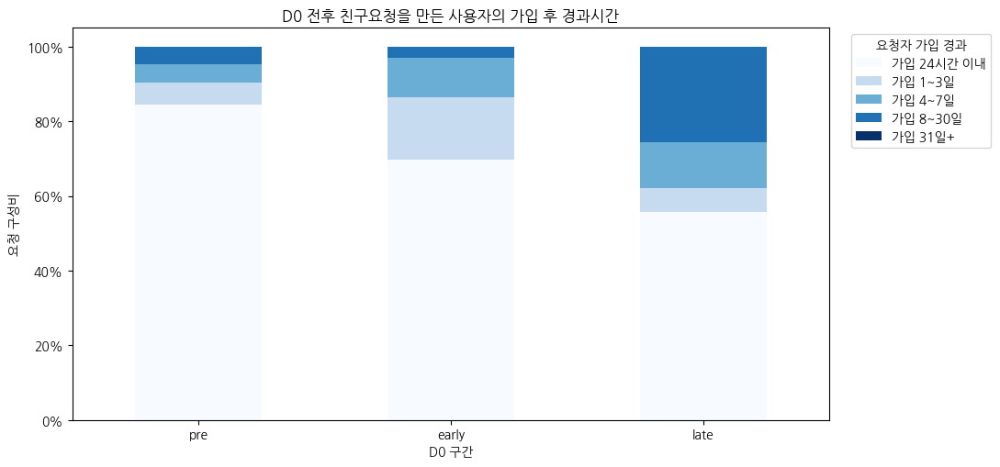

In [ ]:
# D0 전후 요청자의 가입 경과시간
request_age_school = network_con.execute(f'''
WITH d0 AS (
    SELECT school_id,
           MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily
    WHERE current_roster_reached_40_flag=1
    GROUP BY 1
), base AS (
    SELECT e.sender_current_school_id AS school_id,
           e.send_user_id,
           e.final_status_code,
           e.same_school_current_flag,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           EPOCH(CAST(e.request_created_at_raw AS TIMESTAMP)-CAST(p.signup_at AS TIMESTAMP))/3600 AS sender_age_hours
    FROM event e
    JOIN profile p ON e.send_user_id=p.user_id
    JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,
           CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
           CASE WHEN sender_age_hours<0 THEN '가입 이전(시각 이상)'
                WHEN sender_age_hours<24 THEN '가입 24시간 이내'
                WHEN sender_age_hours<72 THEN '가입 1~3일'
                WHEN sender_age_hours<168 THEN '가입 4~7일'
                WHEN sender_age_hours<720 THEN '가입 8~30일'
                ELSE '가입 31일+' END AS sender_age_band
    FROM base
    WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT school_id,phase,sender_age_band,
       COUNT(*) AS requests,COUNT(DISTINCT send_user_id) AS senders,
       SUM(CASE WHEN final_status_code='A' THEN 1 ELSE 0 END) AS eventual_accepted,
       SUM(CASE WHEN same_school_current_flag=1 THEN 1 ELSE 0 END) AS same_school_requests
FROM labeled
GROUP BY 1,2,3
''').fetchdf()

request_age_pooled=(request_age_school.groupby(["phase","sender_age_band"],as_index=False)
                    .agg(requests=("requests","sum"),senders=("senders","sum"),
                         eventual_accepted=("eventual_accepted","sum"),
                         same_school_requests=("same_school_requests","sum")))
request_age_pooled["phase_request_share"]=request_age_pooled.requests/request_age_pooled.groupby("phase").requests.transform("sum")
request_age_pooled["eventual_acceptance_share"]=request_age_pooled.eventual_accepted/request_age_pooled.requests
request_age_pooled["same_school_share"]=request_age_pooled.same_school_requests/request_age_pooled.requests

newcomer_school=(request_age_school.assign(newcomer=lambda x:x.sender_age_band.eq("가입 24시간 이내"))
                 .groupby(["school_id","phase"])
                 .apply(lambda g:pd.Series({"requests":g.requests.sum(),
                                           "newcomer_requests":g.loc[g.newcomer,"requests"].sum()}),
                        include_groups=False).reset_index())
newcomer_school["newcomer_request_share"]=newcomer_school.newcomer_requests/newcomer_school.requests.replace(0,np.nan)
newcomer_wide=newcomer_school.pivot(index="school_id",columns="phase",values="newcomer_request_share")
newcomer_tests=[]
for a,b in [("pre","early"),("early","late")]:
    z=newcomer_wide[[a,b]].dropna(); diff=(z[b]-z[a]).to_numpy(); nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    newcomer_tests.append({"comparison":f"{a}→{b}","schools":len(z),"median_before":z[a].median(),
                           "median_after":z[b].median(),"median_difference":np.median(diff),
                           "share_increased":np.mean(diff>0),"wilcoxon_p":p})
newcomer_tests=pd.DataFrame(newcomer_tests)
display(request_age_pooled.round(4))
display(newcomer_tests.round(4))

age_order=["가입 24시간 이내","가입 1~3일","가입 4~7일","가입 8~30일","가입 31일+","가입 이전(시각 이상)"]
age_chart=request_age_pooled.pivot(index="phase",columns="sender_age_band",values="phase_request_share").fillna(0).reindex(["pre","early","late"])
age_chart=age_chart.reindex(columns=[c for c in age_order if c in age_chart.columns])
age_chart.plot(kind="bar",stacked=True,figsize=(11,5.2),colormap="Blues")
plt.gca().yaxis.set_major_formatter(PercentFormatter(1)); plt.xticks(rotation=0)
plt.xlabel("D0 구간"); plt.ylabel("요청 구성비")
plt.title("D0 전후 친구요청을 만든 사용자의 가입 후 경과시간")
plt.legend(title="요청자 가입 경과",bbox_to_anchor=(1.02,1),loc="upper left")
plt.tight_layout()
plt.show()

plt.close('all')


- 가입 24시간 이내 사용자가 보낸 요청은 첫째 주 전체의 69.82%, 둘째 주에도 55.67%다. 요청량의 절반 이상이 새로 들어온 사용자의 첫날 행동에서 나왔다.
- 전체 요청을 합친 비중이며 학교별 비중의 중앙값과는 계산 기준이 다르다.


,signup_phase,users,early_senders,early_sender_share,continued_users,median_first24_share_of_first14d,median_d0_d7_requests,median_d8_d14_requests,d8_d14_continuation_share_among_early_senders
0,40명 미도달,21572,16321,0.7566,1935,1.0000,6.0,3.0,0.1186
1,40명 이전 가입,151983,139368,0.9170,51252,0.5000,15.0,4.0,0.3677
2,40명 이후 가입,503442,484136,0.9617,90775,0.9348,21.0,2.0,0.1875


,comparison,pre_continuation_share,post_continuation_share,risk_difference_pp,risk_difference_ci_low_pp,risk_difference_ci_high_pp,user_level_chi2,user_level_p,cramers_v,paired_schools,school_median_difference,school_wilcoxon_p
0,40명 이전 가입→이후 가입,0.3677,0.1875,-18.0247,-18.3007,-17.7487,19986.4824,0.0,0.179,3896,-0.1771,0.0


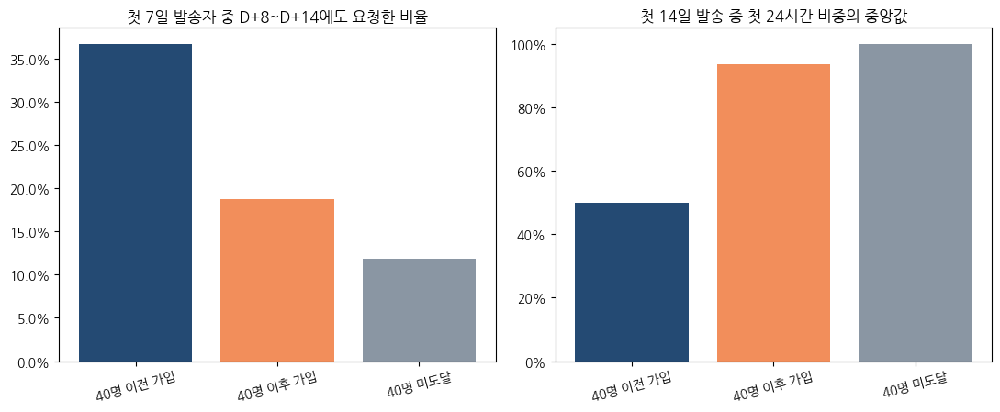

In [ ]:
# 가입 후 첫째 주 발송자의 둘째 주 지속
max_request_ts=network_con.execute("SELECT MAX(CAST(request_created_at_raw AS TIMESTAMP)) FROM event WHERE analysis_eligible_request_flag=1").fetchone()[0]
lifecycle_user=network_con.execute(f'''
WITH eligible AS (
    SELECT user_id,current_school_id,signup_at,current_roster_40th_signup_at,current_friend_list_length,
           CASE WHEN current_roster_40th_signup_at IS NULL THEN '40명 미도달'
                WHEN signup_at<current_roster_40th_signup_at THEN '40명 이전 가입'
                ELSE '40명 이후 가입' END AS signup_phase
    FROM profile
    WHERE analysis_eligible_nonstaff_flag=1
      AND signup_at<=TIMESTAMP '{pd.Timestamp(max_request_ts)-pd.Timedelta(days=14)}'
), counts AS (
    SELECT u.user_id,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 1 DAY THEN 1 ELSE 0 END) AS sent_first_24h_count,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 7 DAY THEN 1 ELSE 0 END) AS sent_d0_d7_count,
           SUM(CASE WHEN e.request_created_at_raw>=u.signup_at+INTERVAL 7 DAY
                     AND e.request_created_at_raw<u.signup_at+INTERVAL 14 DAY THEN 1 ELSE 0 END) AS sent_d8_d14_count
    FROM eligible u
    LEFT JOIN event e ON e.send_user_id=u.user_id
                      AND e.analysis_eligible_request_flag=1
                      AND e.request_created_at_raw>=u.signup_at
                      AND e.request_created_at_raw<u.signup_at+INTERVAL 14 DAY
    GROUP BY 1
)
SELECT u.*,c.sent_first_24h_count,c.sent_d0_d7_count,c.sent_d8_d14_count,
       CASE WHEN c.sent_d0_d7_count>0 THEN 1 ELSE 0 END AS early_sender_flag,
       CASE WHEN c.sent_d0_d7_count>0 AND c.sent_d8_d14_count>0 THEN 1 ELSE 0 END AS continued_d8_d14_flag,
       CASE WHEN c.sent_d0_d7_count+c.sent_d8_d14_count>0
            THEN c.sent_first_24h_count*1.0/(c.sent_d0_d7_count+c.sent_d8_d14_count) END AS first24_share_of_first14d
FROM eligible u JOIN counts c USING(user_id)
''').fetchdf()

lifecycle_summary=(lifecycle_user.groupby("signup_phase",as_index=False)
                   .agg(users=("user_id","size"),early_senders=("early_sender_flag","sum"),
                        early_sender_share=("early_sender_flag","mean"),
                        continued_users=("continued_d8_d14_flag","sum"),
                        median_first24_share_of_first14d=("first24_share_of_first14d","median"),
                        median_d0_d7_requests=("sent_d0_d7_count",lambda s:s[s>0].median()),
                        median_d8_d14_requests=("sent_d8_d14_count",lambda s:s[s>0].median())))
lifecycle_summary["d8_d14_continuation_share_among_early_senders"]=lifecycle_summary.continued_users/lifecycle_summary.early_senders

phase2=lifecycle_user[lifecycle_user.signup_phase.isin(["40명 이전 가입","40명 이후 가입"]) & lifecycle_user.early_sender_flag.eq(1)].copy()
tab=pd.crosstab(phase2.signup_phase,phase2.continued_d8_d14_flag).reindex(index=["40명 이전 가입","40명 이후 가입"],columns=[0,1],fill_value=0)
chi2,p,dof,expected=stats.chi2_contingency(tab)
n=tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(tab.shape[0]-1,tab.shape[1]-1)))
pre_rate=tab.loc["40명 이전 가입",1]/tab.loc["40명 이전 가입"].sum()
post_rate=tab.loc["40명 이후 가입",1]/tab.loc["40명 이후 가입"].sum()
se=math.sqrt(pre_rate*(1-pre_rate)/tab.loc["40명 이전 가입"].sum()+post_rate*(1-post_rate)/tab.loc["40명 이후 가입"].sum())

school_phase=(phase2.groupby(["current_school_id","signup_phase"])
              .agg(senders=("user_id","size"),continued=("continued_d8_d14_flag","sum"))
              .reset_index())
school_phase["continuation_share"]=school_phase.continued/school_phase.senders
school_wide=school_phase.pivot(index="current_school_id",columns="signup_phase",values="continuation_share").dropna()
school_diff=(school_wide["40명 이후 가입"]-school_wide["40명 이전 가입"]).to_numpy()
nz=school_diff[school_diff!=0]; school_stat,school_p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
lifecycle_test=pd.DataFrame([{
    "comparison":"40명 이전 가입→이후 가입","pre_continuation_share":pre_rate,
    "post_continuation_share":post_rate,"risk_difference_pp":100*(post_rate-pre_rate),
    "risk_difference_ci_low_pp":100*((post_rate-pre_rate)-1.96*se),
    "risk_difference_ci_high_pp":100*((post_rate-pre_rate)+1.96*se),
    "user_level_chi2":chi2,"user_level_p":p,"cramers_v":cv,
    "paired_schools":len(school_wide),"school_median_difference":np.median(school_diff),
    "school_wilcoxon_p":school_p
}])
display(lifecycle_summary.round(4))
display(lifecycle_test.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
ls=lifecycle_summary.set_index("signup_phase").reindex(["40명 이전 가입","40명 이후 가입","40명 미도달"])
axes[0].bar(ls.index,ls.d8_d14_continuation_share_among_early_senders,color=[COLORS["navy"],COLORS["orange"],COLORS["gray"]])
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].tick_params(axis="x",rotation=15)
axes[0].set_title("첫 7일 발송자 중 D+8~D+14에도 요청한 비율")
axes[1].bar(ls.index,ls.median_first24_share_of_first14d,color=[COLORS["navy"],COLORS["orange"],COLORS["gray"]])
axes[1].yaxis.set_major_formatter(PercentFormatter(1)); axes[1].tick_params(axis="x",rotation=15)
axes[1].set_title("첫 14일 발송 중 첫 24시간 비중의 중앙값")
plt.tight_layout()
plt.show()

plt.close('all')


- 첫 7일 발송자 중 다음 7일에도 보낸 비율은 40명 이전 가입자 36.77%, 이후 가입자 18.75%다. 이후 가입자는 첫 7일 발송 경험이 더 높아도 둘째 주까지 덜 이어졌다.
- 가입 후 관측 길이를 맞췄지만 가입 시기·구성 차이는 남아 있다.


### 3-2-6. 받은 요청량과 상태 갱신

- 받은 요청 수에 따른 최종 수락·대기·거절 비중을 살펴본다.
- 생성부터 마지막 갱신까지의 간격은 상태 갱신 지연의 대리값이다. 최초 수락 시각과는 다르다.


,load_band,users,requests,accepted,pending,rejected,median_user_acceptance,median_current_friends,accepted_share,pending_share,rejected_share
0,0,16240,0.0,0.0,0.0,0.0,NaN,11.0,NaN,NaN,NaN
2,1,16255,16255.0,5511.0,10591.0,153.0,0.0000,15.0,0.3390,0.6516,0.0094
1,2-5,67577,237052.0,116939.0,117180.0,2933.0,0.5000,22.0,0.4933,0.4943,0.0124
5,6-10,81152,646507.0,396130.0,240812.0,9565.0,0.7778,30.0,0.6127,0.3725,0.0148
6,11-20,145604,2235451.0,1569990.0,626708.0,38753.0,0.8889,39.0,0.7023,0.2803,0.0173
4,21-50,274067,9072182.0,6987643.0,1913267.0,171272.0,0.9310,59.0,0.7702,0.2109,0.0189
3,51+,76186,4939728.0,3802194.0,1030050.0,107484.0,0.9322,92.0,0.7697,0.2085,0.0218


,test,chi2,p_value,cramers_v,accepted_share_at_1,accepted_share_at_21_50
0,수신량 구간×최종 상태,249175.0953,0.0,0.0852,0.339,0.7702


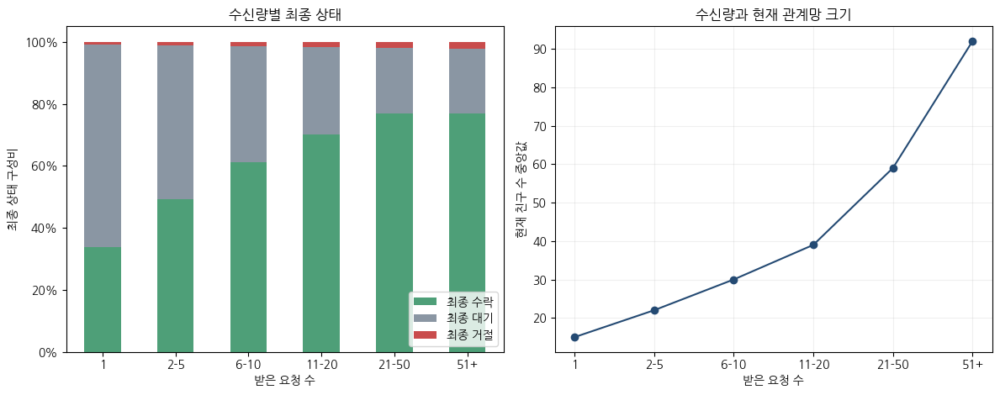

In [ ]:
# 받은 요청량 구간별 최종 상태
receiver_load=network_con.execute('''
WITH u AS (
    SELECT *,
           CASE WHEN received_request_count=0 THEN '0'
                WHEN received_request_count=1 THEN '1'
                WHEN received_request_count<=5 THEN '2-5'
                WHEN received_request_count<=10 THEN '6-10'
                WHEN received_request_count<=20 THEN '11-20'
                WHEN received_request_count<=50 THEN '21-50'
                ELSE '51+' END AS load_band
    FROM profile WHERE analysis_eligible_nonstaff_flag=1
)
SELECT load_band,COUNT(*) AS users,SUM(received_request_count) AS requests,
       SUM(received_final_accepted_count) AS accepted,
       SUM(received_final_pending_count) AS pending,
       SUM(received_final_rejected_count) AS rejected,
       MEDIAN(CASE WHEN received_request_count>0 THEN received_final_accepted_count*1.0/received_request_count END) AS median_user_acceptance,
       MEDIAN(current_friend_list_length) AS median_current_friends
FROM u GROUP BY 1
''').fetchdf()
load_order=["0","1","2-5","6-10","11-20","21-50","51+"]
receiver_load["load_band"]=pd.Categorical(receiver_load.load_band,load_order,ordered=True)
receiver_load=receiver_load.sort_values("load_band")
denom=receiver_load.requests.replace(0,np.nan)
receiver_load["accepted_share"]=receiver_load.accepted/denom
receiver_load["pending_share"]=receiver_load.pending/denom
receiver_load["rejected_share"]=receiver_load.rejected/denom

load_tab=receiver_load[receiver_load.load_band.ne("0")].set_index("load_band")[["accepted","pending","rejected"]]
chi2,p,dof,expected=stats.chi2_contingency(load_tab)
n=load_tab.to_numpy().sum(); cv=math.sqrt(chi2/(n*min(load_tab.shape[0]-1,load_tab.shape[1]-1)))
receiver_test=pd.DataFrame([{"test":"수신량 구간×최종 상태","chi2":chi2,"p_value":p,"cramers_v":cv,
                            "accepted_share_at_1":float(receiver_load.loc[receiver_load.load_band.eq("1"),"accepted_share"].iloc[0]),
                            "accepted_share_at_21_50":float(receiver_load.loc[receiver_load.load_band.eq("21-50"),"accepted_share"].iloc[0])}])
display(receiver_load.round(4))
display(receiver_test.round(4))

chart=receiver_load[receiver_load.load_band.ne("0")].set_index("load_band")
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
chart[["accepted_share","pending_share","rejected_share"]].plot(kind="bar",stacked=True,ax=axes[0],
    color=[COLORS["green"],COLORS["gray"],COLORS["red"]])
axes[0].yaxis.set_major_formatter(PercentFormatter(1)); axes[0].tick_params(axis="x",rotation=0)
axes[0].set_xlabel("받은 요청 수"); axes[0].set_ylabel("최종 상태 구성비"); axes[0].set_title("수신량별 최종 상태")
axes[0].legend(["최종 수락","최종 대기","최종 거절"],loc="lower right")
axes[1].plot(chart.index.astype(str),chart.median_current_friends,marker="o",color=COLORS["navy"])
axes[1].set_xlabel("받은 요청 수"); axes[1].set_ylabel("현재 친구 수 중앙값"); axes[1].set_title("수신량과 현재 관계망 크기")
axes[1].grid(alpha=.2)
plt.tight_layout()
plt.show()

plt.close('all')


- 요청 1건 수신자의 최종 수락 비중은 33.90%, 21~50건 수신자는 77.02%다. 많이 받은 집단에서 수락 비중이 급격히 떨어지지는 않았다.
- 다만 활동성과 관계망 크기가 함께 다르다. 요청이 적은 사용자의 낮은 수락 비중도 살펴볼 부분이다.


,phase,same_school_current_flag,accepted_requests,median_delay_hours,p75_delay_hours,p90_delay_hours,within_3h_share,within_24h_share
0,early,0,1326705,5.9464,22.6228,73.1853,0.3927,0.7638
1,early,1,6900905,3.8539,19.2836,64.4664,0.4623,0.7937
2,late,0,335659,13.1242,45.8528,122.8585,0.2681,0.6306
3,late,1,997060,12.3240,46.0392,135.8693,0.2865,0.6357
4,pre,0,146822,7.9781,28.0879,92.9338,0.3650,0.7222
5,pre,1,280513,26.8617,81.7631,160.2070,0.2018,0.4721


,phase,accepted_requests,median_delay_hours,p90_delay_hours,within_3h_share,within_24h_share
0,early,8227610,4.1558,66.4059,0.4511,0.7889
1,late,1332719,12.5458,132.0713,0.2819,0.6344
2,pre,427335,19.3236,143.1328,0.2579,0.5581


,comparison,schools,median_before,median_after,median_difference,share_delay_increased,wilcoxon_p
0,pre→early,3246,23.4535,5.5907,-16.9532,0.1285,0.0
1,early→late,3630,5.3031,20.1658,13.5542,0.9317,0.0


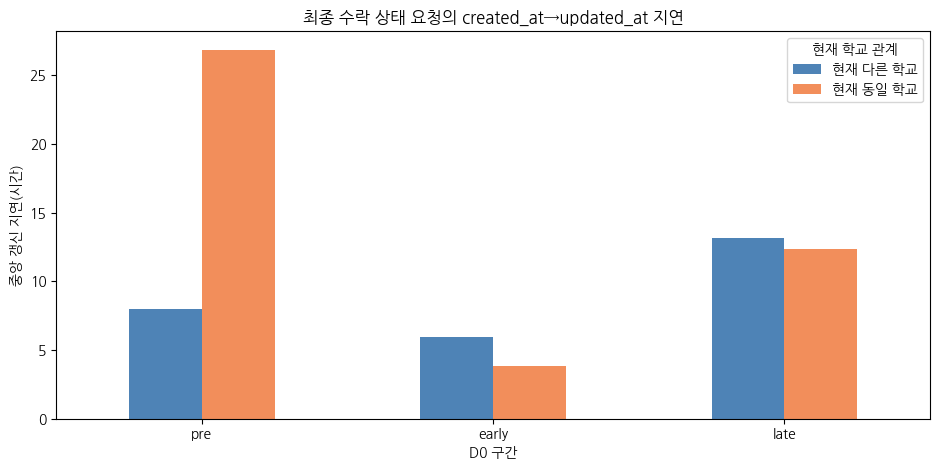

In [ ]:
# 최종 수락 요청의 마지막 갱신까지 간격
accepted_delay=network_con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT e.sender_current_school_id AS school_id,e.same_school_current_flag,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                  WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                  WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase
    FROM x WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT phase,same_school_current_flag,COUNT(*) AS accepted_requests,
       MEDIAN(delay_seconds)/3600 AS median_delay_hours,
       QUANTILE_CONT(delay_seconds,.75)/3600 AS p75_delay_hours,
       QUANTILE_CONT(delay_seconds,.9)/3600 AS p90_delay_hours,
       AVG(CASE WHEN delay_seconds<=10800 THEN 1.0 ELSE 0 END) AS within_3h_share,
       AVG(CASE WHEN delay_seconds<=86400 THEN 1.0 ELSE 0 END) AS within_24h_share
FROM labeled GROUP BY 1,2 ORDER BY 1,2
''').fetchdf()

accepted_delay_overall=network_con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
), labeled AS (
    SELECT *,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                  WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                  WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase
    FROM x WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
)
SELECT phase,COUNT(*) AS accepted_requests,MEDIAN(delay_seconds)/3600 AS median_delay_hours,
       QUANTILE_CONT(delay_seconds,.9)/3600 AS p90_delay_hours,
       AVG(CASE WHEN delay_seconds<=10800 THEN 1.0 ELSE 0 END) AS within_3h_share,
       AVG(CASE WHEN delay_seconds<=86400 THEN 1.0 ELSE 0 END) AS within_24h_share
FROM labeled GROUP BY 1 ORDER BY 1
''').fetchdf()

delay_school=network_con.execute(f'''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), x AS (
    SELECT e.sender_current_school_id AS school_id,
           DATE_DIFF('day',d.d0_date,CAST(e.request_created_at_raw AS DATE)) AS rel_day,
           e.created_to_last_update_seconds AS delay_seconds
    FROM event e JOIN d0 d ON e.sender_current_school_id=d.school_id
    WHERE e.analysis_eligible_request_flag=1 AND e.final_status_code='A'
      AND e.created_to_last_update_seconds>=0
      AND d.d0_date BETWEEN DATE '{(min_event_date + pd.Timedelta(days=14)).date()}'
                          AND DATE '{(max_event_date - pd.Timedelta(days=14)).date()}'
)
SELECT school_id,CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
                      WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
                      WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
       MEDIAN(delay_seconds)/3600 AS median_delay_hours,COUNT(*) AS accepted_requests
FROM x
WHERE rel_day BETWEEN -7 AND -1 OR rel_day BETWEEN 1 AND 7 OR rel_day BETWEEN 8 AND 14
GROUP BY 1,2 HAVING COUNT(*)>=5
''').fetchdf()
delay_wide=delay_school.pivot(index="school_id",columns="phase",values="median_delay_hours")
delay_tests=[]
for a,b in [("pre","early"),("early","late")]:
    z=delay_wide[[a,b]].dropna(); diff=(z[b]-z[a]).to_numpy(); nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    delay_tests.append({"comparison":f"{a}→{b}","schools":len(z),"median_before":z[a].median(),
                        "median_after":z[b].median(),"median_difference":np.median(diff),
                        "share_delay_increased":np.mean(diff>0),"wilcoxon_p":p})
delay_tests=pd.DataFrame(delay_tests)
display(accepted_delay.round(4))
display(accepted_delay_overall.round(4))
display(delay_tests.round(4))

delay_chart=accepted_delay.copy()
delay_chart["relation"]=delay_chart.same_school_current_flag.map({1:"현재 동일 학교",0:"현재 다른 학교"})
dc=delay_chart.pivot(index="phase",columns="relation",values="median_delay_hours").reindex(["pre","early","late"])
dc.plot(kind="bar",figsize=(9.5,4.8),color=[COLORS["blue"],COLORS["orange"]])
plt.xticks(rotation=0); plt.xlabel("D0 구간"); plt.ylabel("중앙 갱신 지연(시간)")
plt.title("최종 수락 상태 요청의 created_at→updated_at 지연")
plt.legend(title="현재 학교 관계")
plt.tight_layout()
plt.show()

plt.close('all')


- 최종 수락 요청의 생성부터 마지막 갱신까지 중앙 간격은 첫째 주 약 4.16시간, 둘째 주 약 12.55시간이다. 둘째 주에 갱신 간격이 길어졌다.


### 3-2-7. 초기 요청 강도와 비교 기준 점검

- 첫째 주 요청량이 다른 학교들의 둘째 주 절대 요청량을 살펴본다.
- 기준일과 전후 비교 기간을 바꿔도 같은 변화가 나타나는지 점검한다.


,early_intensity_quintile,schools,early_request_rate_median,late_request_rate_median,retention_ratio_median,early_sender_reach_median,early_acceptance_median,early_same_school_median,early_new_user_rate_median
0,Q1 낮음,757,605.3097,152.9412,0.2811,85.1852,0.6688,0.7724,22.7273
1,Q2,757,1143.0622,218.4211,0.1935,135.7143,0.7638,0.7887,40.0000
2,Q3,756,1495.1279,223.1667,0.1524,158.1602,0.7741,0.8416,47.7648
3,Q4,757,1862.4506,206.0086,0.1117,176.4706,0.7776,0.8760,55.1351
4,Q5 높음,757,2423.1156,210.3226,0.0856,195.6044,0.7793,0.9067,62.6016


,schools,spearman_early_vs_late_absolute,p_early_vs_late_absolute,spearman_early_vs_retention_ratio,p_early_vs_retention_ratio,late_absolute_kruskal_h,late_absolute_kruskal_p,temporal_holdout_r2_from_section11
0,3784,0.0546,0.0008,-0.3977,0.0,49.4337,0.0,-0.9614


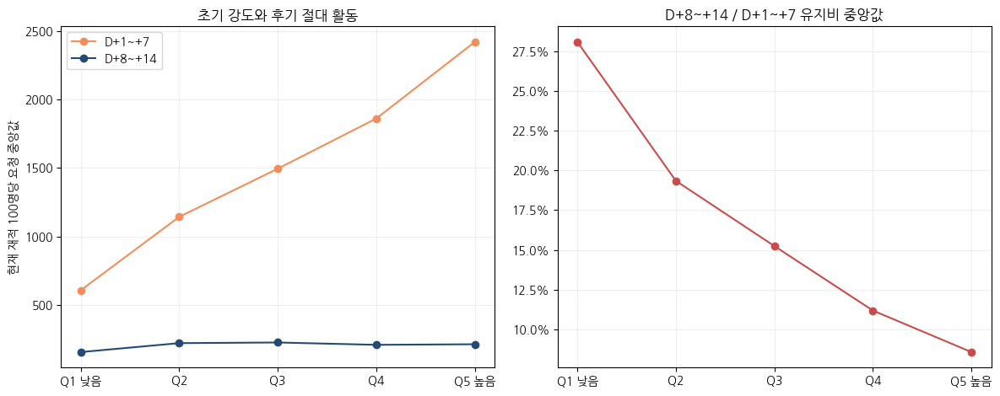

In [ ]:
# 초기 요청 강도 구간별 후기 활동
persistence=wide.dropna(subset=["requests_per_100_roster_early","requests_per_100_roster_late"]).copy()
persistence=persistence[persistence.requests_per_100_roster_early>0].copy()
persistence["early_intensity_quintile"]=pd.qcut(persistence.requests_per_100_roster_early,5,
    labels=["Q1 낮음","Q2","Q3","Q4","Q5 높음"])
persistence["late_to_early_ratio"]=persistence.requests_per_100_roster_late/persistence.requests_per_100_roster_early
persistence_summary=(persistence.groupby("early_intensity_quintile",observed=True)
                     .agg(schools=("school_id","size"),
                          early_request_rate_median=("requests_per_100_roster_early","median"),
                          late_request_rate_median=("requests_per_100_roster_late","median"),
                          retention_ratio_median=("late_to_early_ratio","median"),
                          early_sender_reach_median=("sender_days_per_100_roster_early","median"),
                          early_acceptance_median=("eventual_acceptance_share_early","median"),
                          early_same_school_median=("same_school_share_early","median"),
                          early_new_user_rate_median=("new_users_per_100_roster_early","median"))
                     .reset_index())

rho_abs,p_abs=stats.spearmanr(persistence.requests_per_100_roster_early,persistence.requests_per_100_roster_late)
rho_ratio,p_ratio=stats.spearmanr(persistence.requests_per_100_roster_early,persistence.late_to_early_ratio)
groups=[g.requests_per_100_roster_late.to_numpy() for _,g in persistence.groupby("early_intensity_quintile",observed=True)]
kw,p_kw=stats.kruskal(*groups)
persistence_test=pd.DataFrame([{"schools":len(persistence),
    "spearman_early_vs_late_absolute":rho_abs,"p_early_vs_late_absolute":p_abs,
    "spearman_early_vs_retention_ratio":rho_ratio,"p_early_vs_retention_ratio":p_ratio,
    "late_absolute_kruskal_h":kw,"late_absolute_kruskal_p":p_kw,
    "temporal_holdout_r2_from_section11":float(model_quality.test_r2.iloc[0])}])
display(persistence_summary.round(4))
display(persistence_test.round(4))

x=np.arange(len(persistence_summary))
fig,axes=plt.subplots(1,2,figsize=(12,4.8))
axes[0].plot(x,persistence_summary.early_request_rate_median,marker="o",label="D+1~+7",color=COLORS["orange"])
axes[0].plot(x,persistence_summary.late_request_rate_median,marker="o",label="D+8~+14",color=COLORS["navy"])
axes[0].set_xticks(x,persistence_summary.early_intensity_quintile.astype(str)); axes[0].legend()
axes[0].set_ylabel("현재 재적 100명당 요청 중앙값"); axes[0].set_title("초기 강도와 후기 절대 활동")
axes[1].plot(x,persistence_summary.retention_ratio_median,marker="o",color=COLORS["red"])
axes[1].set_xticks(x,persistence_summary.early_intensity_quintile.astype(str))
axes[1].yaxis.set_major_formatter(PercentFormatter(1)); axes[1].set_title("D+8~+14 / D+1~+7 유지비 중앙값")
for ax in axes: ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

plt.close('all')


- 첫째 주와 둘째 주 요청량의 순위상관은 0.0546으로 매우 약하다. 초기 최저·최고 구간의 후기 요청량 중앙값은 재적 100명당 약 152.94건과 210.32건이다.
- 초기 격차에 비해 후기 격차가 작다. 초기 대비 후기 비율은 분모의 영향을 받으므로 절대 요청량을 함께 봐야 한다.


,anchor_offset,metric,schools,median_difference,mean_difference,share_increased,wilcoxon_p
0,0,requests_per_100,3896,1385.9082,1358.0509,0.9394,0.0000
1,0,sender_days_per_100,3896,142.9198,129.9043,0.9523,0.0000
2,0,national_share,3896,516.1239,952.9397,0.9374,0.0000
3,21,requests_per_100,3896,-42.6018,-72.1036,0.1088,0.0000
4,21,sender_days_per_100,3896,-8.8186,-11.8059,0.0480,0.0000
5,21,national_share,3896,-2.3743,2.8390,0.4636,0.1342
6,28,requests_per_100,3896,-12.1584,-27.3080,0.1301,0.0000
7,28,sender_days_per_100,3896,-3.5211,-4.7889,0.0603,0.0000
8,28,national_share,3896,-3.9528,25.1182,0.4073,0.0059
9,35,requests_per_100,3896,-2.4019,-9.3744,0.1702,0.0000


,horizon_days,metric,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,3,requests_per_100_roster,3792,45.3203,953.3444,862.4162,0.9072,0.0
1,3,sender_days_per_100_roster,3792,8.6048,90.5933,79.1438,0.9169,0.0
2,5,requests_per_100_roster,3792,54.1886,1284.4281,1190.5974,0.9277,0.0
3,5,sender_days_per_100_roster,3792,10.1707,129.8851,117.3831,0.9372,0.0
4,7,requests_per_100_roster,3792,59.2243,1493.0024,1393.4279,0.9380,0.0
5,7,sender_days_per_100_roster,3792,11.1111,156.9482,143.2836,0.9507,0.0


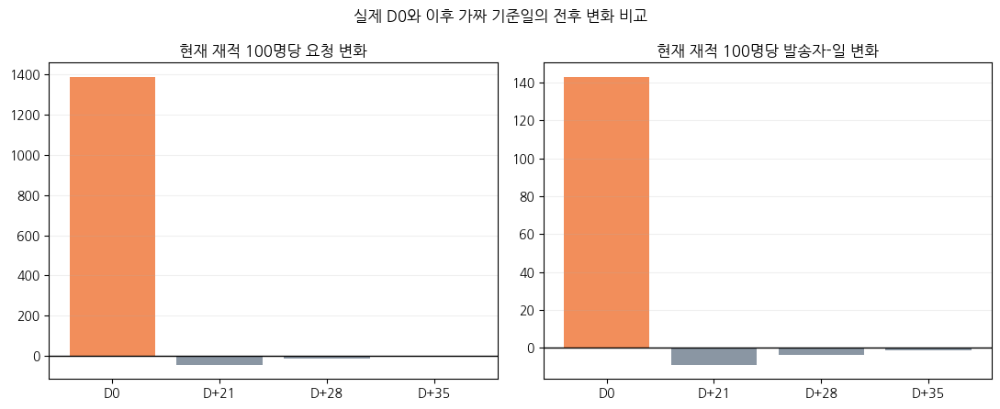

In [ ]:
# 가상 기준일·전후 관측 폭 민감도
placebo_school=network_con.execute('''
WITH d0 AS (
    SELECT school_id,MAX(CAST(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP) AS DATE)) AS d0_date,
           MAX(current_roster_nonstaff_account_count) AS roster_size
    FROM school_daily WHERE current_roster_reached_40_flag=1 GROUP BY 1
), national AS (
    SELECT CAST(activity_date AS DATE) AS activity_date,SUM(sent_request_created_count) AS national_requests
    FROM school_daily WHERE analysis_eligible_school_day_flag=1 GROUP BY 1
), offsets AS (
    SELECT * FROM (VALUES (0),(21),(28),(35)) AS t(anchor_offset)
), joined AS (
    SELECT d.school_id,o.anchor_offset,
           DATE_DIFF('day',CAST(d.d0_date+o.anchor_offset*INTERVAL 1 DAY AS DATE),CAST(s.activity_date AS DATE)) AS rel_day,
           100.0*s.sent_request_created_count/NULLIF(d.roster_size,0) AS requests_per_100_day,
           100.0*s.sent_request_user_count/NULLIF(d.roster_size,0) AS sender_days_per_100_day,
           1000000.0*s.sent_request_created_count/NULLIF(n.national_requests,0) AS national_share_per_million
    FROM d0 d CROSS JOIN offsets o
    JOIN school_daily s ON s.school_id=d.school_id
    JOIN national n ON CAST(s.activity_date AS DATE)=n.activity_date
    WHERE DATE_DIFF('day',CAST(d.d0_date+o.anchor_offset*INTERVAL 1 DAY AS DATE),CAST(s.activity_date AS DATE)) BETWEEN -7 AND 7
)
SELECT school_id,anchor_offset,
       SUM(CASE WHEN rel_day BETWEEN -7 AND -1 THEN requests_per_100_day ELSE 0 END) AS pre_requests_per_100,
       SUM(CASE WHEN rel_day BETWEEN 1 AND 7 THEN requests_per_100_day ELSE 0 END) AS post_requests_per_100,
       SUM(CASE WHEN rel_day BETWEEN -7 AND -1 THEN sender_days_per_100_day ELSE 0 END) AS pre_sender_days_per_100,
       SUM(CASE WHEN rel_day BETWEEN 1 AND 7 THEN sender_days_per_100_day ELSE 0 END) AS post_sender_days_per_100,
       AVG(CASE WHEN rel_day BETWEEN -7 AND -1 THEN national_share_per_million END) AS pre_national_share,
       AVG(CASE WHEN rel_day BETWEEN 1 AND 7 THEN national_share_per_million END) AS post_national_share,
       COUNT(CASE WHEN rel_day BETWEEN -7 AND -1 THEN 1 END) AS pre_days,
       COUNT(CASE WHEN rel_day BETWEEN 1 AND 7 THEN 1 END) AS post_days
FROM joined GROUP BY 1,2
HAVING pre_days=7 AND post_days=7
''').fetchdf()

placebo_rows=[]
for offset,g in placebo_school.groupby("anchor_offset"):
    for stem in ["requests_per_100","sender_days_per_100","national_share"]:
        diff=(g[f"post_{stem}"]-g[f"pre_{stem}"]).dropna().to_numpy()
        nz=diff[diff!=0]; stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        placebo_rows.append({"anchor_offset":offset,"metric":stem,"schools":len(diff),
                             "median_difference":np.median(diff),"mean_difference":np.mean(diff),
                             "share_increased":np.mean(diff>0),"wilcoxon_p":p})
placebo_tests=pd.DataFrame(placebo_rows)

sensitivity_rows=[]
for horizon in [3,5,7]:
    for metric in ["requests_per_100_roster","sender_days_per_100_roster"]:
        pre=(school_event[school_event.rel_day.between(-horizon,-1)]
             .groupby("school_id")[metric].sum())
        post=(school_event[school_event.rel_day.between(1,horizon)]
              .groupby("school_id")[metric].sum())
        z=pd.concat([pre.rename("pre"),post.rename("post")],axis=1).dropna()
        diff=(z.post-z.pre).to_numpy(); nz=diff[diff!=0]
        stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        sensitivity_rows.append({"horizon_days":horizon,"metric":metric,"schools":len(z),
                                 "median_before":z.pre.median(),"median_after":z.post.median(),
                                 "median_difference":np.median(diff),"share_increased":np.mean(diff>0),
                                 "wilcoxon_p":p})
sensitivity_tests=pd.DataFrame(sensitivity_rows)
display(placebo_tests.round(4))
display(sensitivity_tests.round(4))

pp=placebo_tests[placebo_tests.metric.isin(["requests_per_100","sender_days_per_100"])].copy()
fig,axes=plt.subplots(1,2,figsize=(11,4.5))
for ax,(metric,title) in zip(axes,[("requests_per_100","현재 재적 100명당 요청 변화"),
                                  ("sender_days_per_100","현재 재적 100명당 발송자-일 변화")]):
    q=pp[pp.metric.eq(metric)].sort_values("anchor_offset")
    colors=[COLORS["orange"] if x==0 else COLORS["gray"] for x in q.anchor_offset]
    anchor_labels=["D0" if x==0 else f"D+{x}" for x in q.anchor_offset]
    ax.bar(anchor_labels,q.median_difference,color=colors)
    ax.axhline(0,color="black",lw=1); ax.set_title(title); ax.grid(axis="y",alpha=.2)
plt.suptitle("실제 D0와 이후 가짜 기준일의 전후 변화 비교")
plt.tight_layout()
plt.show()

plt.close('all')


- 실제 D0에서는 요청량이 늘었지만 기준일을 21·28·35일 뒤로 옮기면 중앙 변화가 음수였다. 비교 폭을 3·5·7일로 바꿔도 실제 D0의 증가 방향은 유지됐다.
- 특정 기간을 골라서만 나온 결과는 아니지만, D0 자체가 가입 규모로 정해지는 특성은 남는다.


### 3-2-8. 학교 안에서 관계가 연결된 모습

- 최종 수락된 같은 학교 요청쌍으로 관계망을 만들고 고립, 연결 집단, 학년·반별 연결을 살펴본다.
- 현재 소속과 최종 요청 상태로 만든 관계망이다. 구간별 분석도 요청 생성일 기준이며 당시의 실제 친구 목록을 복원한 것은 아니다.


,node_count,school_count,accepted_undirected_edge_count,self_edges,duplicated_edges,cross_school_edges
0,677080,5551,10377675,0,0,0


,count,mean,std,min,10%,25%,50%,75%,90%,max
n_users,3897.0,168.2063,86.7647,40.0000,67.0000,100.0000,154.0000,225.0000,288.0000,578.0000
accepted_edge_count,3897.0,2650.7873,1938.8291,11.0000,547.6000,1092.0000,2239.0000,3824.0000,5388.2000,15197.0000
active_user_share,3897.0,0.9556,0.0451,0.3542,0.9129,0.9481,0.9671,0.9798,0.9889,1.0000
isolate_share,3897.0,0.0444,0.0451,0.0000,0.0111,0.0202,0.0329,0.0519,0.0871,0.6458
average_degree,3897.0,28.9524,11.9326,0.5238,13.3552,20.2922,28.7303,37.2449,44.3218,80.5063
density,3897.0,0.2053,0.1122,0.0128,0.0907,0.1211,0.1802,0.2626,0.3564,0.8038
largest_component_share,3897.0,0.9525,0.0534,0.1429,0.9058,0.9455,0.9659,0.9796,0.9887,1.0000
component_count,3897.0,7.3803,4.5133,1.0000,2.0000,4.0000,7.0000,10.0000,13.0000,37.0000
degree_gini,3897.0,0.3526,0.0644,0.1122,0.2796,0.3133,0.3478,0.3877,0.4303,0.7758
degree_centralization,3897.0,0.3618,0.1029,0.0852,0.2263,0.2861,0.3616,0.4371,0.4945,0.6579


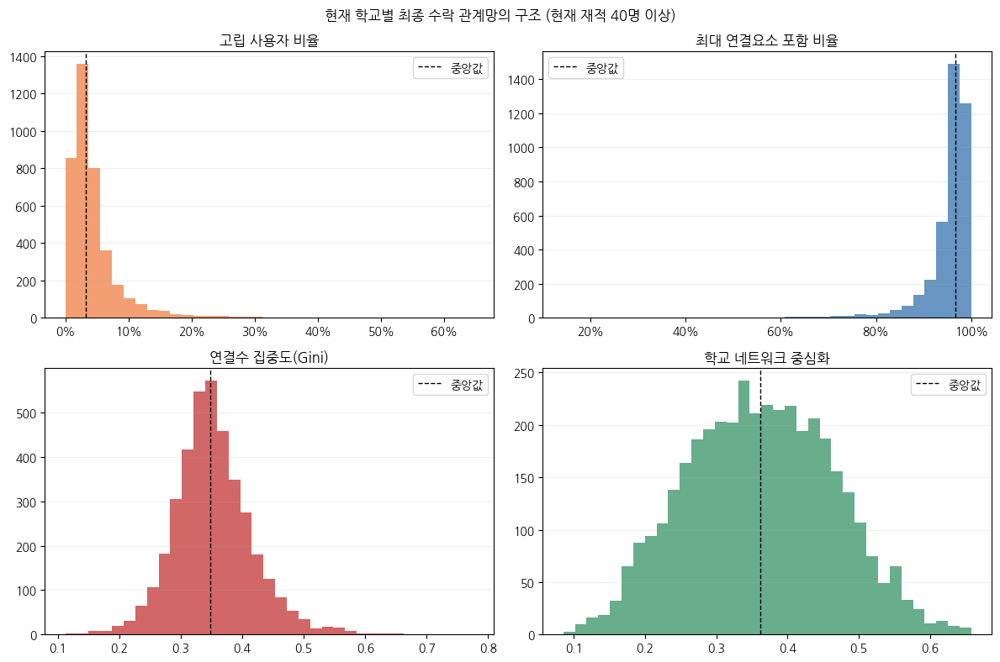

In [ ]:
# 동일 학교 최종 수락 관계망 구성·기초 분포
network_con.execute('''
CREATE OR REPLACE TEMP TABLE graph_nodes AS
SELECT
    CAST(user_id AS BIGINT) AS user_id,
    CAST(current_school_id AS BIGINT) AS school_id,
    TRY_CAST(current_grade AS BIGINT) AS current_grade,
    TRY_CAST(current_class_num AS BIGINT) AS current_class_num,
    TRY_CAST(current_group_id AS BIGINT) AS current_group_id,
    TRY_CAST(signup_at AS TIMESTAMP) AS signup_at,
    CAST(ROW_NUMBER() OVER (ORDER BY user_id)-1 AS INTEGER) AS node_idx
FROM profile
WHERE analysis_eligible_nonstaff_flag=1
  AND current_school_id IS NOT NULL
''')

network_con.execute('''
CREATE OR REPLACE TEMP TABLE accepted_school_edges AS
SELECT DISTINCT
    ns.school_id,
    LEAST(ns.node_idx,nr.node_idx)::INTEGER AS u_idx,
    GREATEST(ns.node_idx,nr.node_idx)::INTEGER AS v_idx,
    LEAST(p.send_user_id,p.receive_user_id)::BIGINT AS user_a,
    GREATEST(p.send_user_id,p.receive_user_id)::BIGINT AS user_b
FROM pair p
JOIN graph_nodes ns ON ns.user_id=p.send_user_id
JOIN graph_nodes nr ON nr.user_id=p.receive_user_id
WHERE p.analysis_eligible_pair_flag=1
  AND p.same_school_current_flag=1
  AND p.final_accepted_record_count>0
  AND ns.school_id=nr.school_id
  AND ns.node_idx<>nr.node_idx
''')

graph_qa=network_con.execute('''
SELECT
  (SELECT COUNT(*) FROM graph_nodes) AS node_count,
  (SELECT COUNT(DISTINCT school_id) FROM graph_nodes) AS school_count,
  (SELECT COUNT(*) FROM accepted_school_edges) AS accepted_undirected_edge_count,
  (SELECT COUNT(*) FROM accepted_school_edges WHERE u_idx=v_idx) AS self_edges,
  (SELECT COUNT(*) FROM (
     SELECT u_idx,v_idx,COUNT(*) n FROM accepted_school_edges GROUP BY 1,2 HAVING n>1
   )) AS duplicated_edges,
  (SELECT COUNT(*) FROM accepted_school_edges e
     JOIN graph_nodes a ON a.node_idx=e.u_idx
     JOIN graph_nodes b ON b.node_idx=e.v_idx
   WHERE a.school_id<>b.school_id OR a.school_id<>e.school_id) AS cross_school_edges
''').fetchdf()

assert int(graph_qa.self_edges.iloc[0])==0
assert int(graph_qa.duplicated_edges.iloc[0])==0
assert int(graph_qa.cross_school_edges.iloc[0])==0
display(graph_qa)

node_graph=network_con.execute('''
SELECT node_idx,user_id,school_id,current_grade,current_class_num,current_group_id,signup_at
FROM graph_nodes ORDER BY node_idx
''').fetchdf()
edge_np=network_con.execute('SELECT u_idx,v_idx FROM accepted_school_edges ORDER BY u_idx,v_idx').fetchnumpy()
edge_u=edge_np["u_idx"].astype(np.int32,copy=False)
edge_v=edge_np["v_idx"].astype(np.int32,copy=False)
n_nodes=len(node_graph)
rows=np.concatenate([edge_u,edge_v])
cols=np.concatenate([edge_v,edge_u])
accepted_adj=sparse.csr_matrix((np.ones(len(rows),dtype=np.uint8),(rows,cols)),shape=(n_nodes,n_nodes))
accepted_adj.sum_duplicates()
accepted_adj.data[:]=1
del rows,cols,edge_np

_,component_label=connected_components(accepted_adj,directed=False,return_labels=True)
accepted_degree=np.diff(accepted_adj.indptr).astype(np.int32)
node_graph["accepted_degree"]=accepted_degree
node_graph["component_label"]=component_label
node_graph["active_node_flag"]=(accepted_degree>0).astype(int)

component_sizes=(node_graph.groupby(["school_id","component_label"],as_index=False)
                 .size().rename(columns={"size":"component_size"}))
largest_component=(component_sizes.groupby("school_id",as_index=False).component_size.max()
                   .rename(columns={"component_size":"largest_component_users"}))
component_count=(component_sizes.groupby("school_id",as_index=False).size()
                 .rename(columns={"size":"component_count"}))

def degree_gini(values):
    x=np.asarray(values,dtype=float)
    if len(x)==0 or x.sum()==0:
        return 0.0
    x=np.sort(x)
    return float((2*np.arange(1,len(x)+1)-len(x)-1).dot(x)/(len(x)*x.sum()))

school_structure=(node_graph.groupby("school_id",as_index=False)
                  .agg(n_users=("user_id","size"),
                       active_users=("active_node_flag","sum"),
                       total_degree=("accepted_degree","sum"),
                       max_degree=("accepted_degree","max"),
                       median_degree=("accepted_degree","median")))
degree_gini_school=(node_graph.groupby("school_id").accepted_degree.apply(degree_gini)
                    .rename("degree_gini").reset_index())
school_structure=(school_structure.merge(largest_component,on="school_id",how="left")
                  .merge(component_count,on="school_id",how="left")
                  .merge(degree_gini_school,on="school_id",how="left"))
school_structure["accepted_edge_count"]=(school_structure.total_degree//2).astype(np.int64)
school_structure["isolated_users"]=school_structure.n_users-school_structure.active_users
school_structure["active_user_share"]=school_structure.active_users/school_structure.n_users
school_structure["isolate_share"]=school_structure.isolated_users/school_structure.n_users
school_structure["average_degree"]=school_structure.total_degree/school_structure.n_users
school_structure["density"]=np.where(
    school_structure.n_users>1,
    school_structure.total_degree/(school_structure.n_users*(school_structure.n_users-1)),np.nan)
school_structure["largest_component_share"]=school_structure.largest_component_users/school_structure.n_users
school_structure["fragmentation_share"]=1-school_structure.largest_component_share
school_structure["degree_centralization"]=np.where(
    school_structure.n_users>2,
    (school_structure.n_users*school_structure.max_degree-school_structure.total_degree)/
    ((school_structure.n_users-1)*(school_structure.n_users-2)),np.nan)

d0_flags=network_con.execute('''
SELECT school_id,
       MAX(current_roster_reached_40_flag) AS reached_40_flag,
       MAX(TRY_CAST(current_roster_40th_signup_at AS TIMESTAMP)) AS d0_at
FROM school_daily GROUP BY 1
''').fetchdf()
school_structure=school_structure.merge(d0_flags,on="school_id",how="left")
school_structure["reached_40_flag"]=school_structure.reached_40_flag.fillna(0).astype(int)

structure_summary=(school_structure[school_structure.n_users>=40]
                   [["n_users","accepted_edge_count","active_user_share","isolate_share",
                     "average_degree","density","largest_component_share","component_count",
                     "degree_gini","degree_centralization"]]
                   .describe(percentiles=[.1,.25,.5,.75,.9]).T)
display(structure_summary.round(4))

plot_structure=school_structure[school_structure.n_users>=40].copy()
fig,axes=plt.subplots(2,2,figsize=(12,8))
for ax,(col,title,color) in zip(axes.ravel(),[
    ("isolate_share","고립 사용자 비율",COLORS["orange"]),
    ("largest_component_share","최대 연결요소 포함 비율",COLORS["blue"]),
    ("degree_gini","연결수 집중도(Gini)",COLORS["red"]),
    ("degree_centralization","학교 네트워크 중심화",COLORS["green"]) ]):
    ax.hist(plot_structure[col].dropna(),bins=35,color=color,alpha=.85)
    ax.axvline(plot_structure[col].median(),color="black",ls="--",lw=1,label="중앙값")
    ax.set_title(title); ax.legend(); ax.grid(axis="y",alpha=.2)
    if "share" in col: ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.suptitle("현재 학교별 최종 수락 관계망의 구조 (현재 재적 40명 이상)")
plt.tight_layout()
plt.show()

plt.close('all')


- 현재 학교가 있는 일반 사용자 677,080명과 최종 수락 관계쌍 10,377,675개로 관계망을 만들었다. 자기·중복·타학교 연결은 없었다.
- 40명 이상 학교에서 고립 비율 중앙값은 3.29%, 가장 큰 연결 집단의 비율은 96.59%다. 대부분이 한 집단으로 연결돼 있었다.


,predictor,outcome,schools,spearman_rho,p_value
0,reciprocal_request_pair_share,largest_component_share,3897,0.1798,0.0
1,reciprocal_request_pair_share,isolate_share,3897,-0.1843,0.0
2,reciprocal_request_pair_share,degree_gini,3897,-0.1455,0.0
3,reciprocal_request_pair_share,degree_centralization,3897,0.0690,0.0


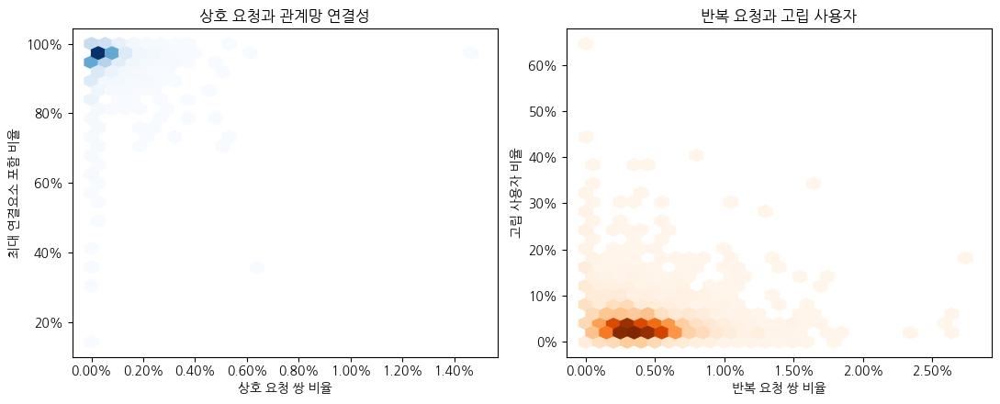

In [ ]:
# 역방향 요청과 관계망 연결 정도
reciprocity=network_con.execute('''
WITH directional AS (
  SELECT
    sender_current_school_id AS school_id,
    LEAST(send_user_id,receive_user_id) AS user_a,
    GREATEST(send_user_id,receive_user_id) AS user_b,
    send_user_id,receive_user_id,
    request_record_count,
    final_accepted_record_count,
    repeated_directional_pair_flag
  FROM pair
  WHERE analysis_eligible_pair_flag=1
    AND same_school_current_flag=1
), canonical AS (
  SELECT school_id,user_a,user_b,
         COUNT(*) AS direction_count,
         SUM(request_record_count) AS request_record_count,
         SUM(CASE WHEN final_accepted_record_count>0 THEN 1 ELSE 0 END) AS accepted_direction_count,
         MAX(repeated_directional_pair_flag) AS repeated_direction_flag
  FROM directional GROUP BY 1,2,3
)
SELECT school_id,
       COUNT(*) AS request_pair_count,
       SUM(direction_count) AS directed_pair_count,
       SUM(request_record_count) AS request_record_count,
       SUM(direction_count=2)::BIGINT AS reciprocal_request_pair_count,
       SUM(accepted_direction_count>0)::BIGINT AS accepted_pair_count,
       SUM(accepted_direction_count=2)::BIGINT AS mutual_accepted_pair_count,
       SUM(repeated_direction_flag)::BIGINT AS repeated_pair_count
FROM canonical GROUP BY 1
''').fetchdf()
reciprocity["reciprocal_request_pair_share"]=reciprocity.reciprocal_request_pair_count/reciprocity.request_pair_count
reciprocity["mutual_accepted_share_among_accepted_pairs"]=reciprocity.mutual_accepted_pair_count/reciprocity.accepted_pair_count.replace(0,np.nan)
reciprocity["repeated_pair_share"]=reciprocity.repeated_pair_count/reciprocity.request_pair_count
school_structure=school_structure.merge(reciprocity,on="school_id",how="left")
fill_zero=["request_pair_count","directed_pair_count","request_record_count","reciprocal_request_pair_count",
           "accepted_pair_count","mutual_accepted_pair_count","repeated_pair_count",
           "reciprocal_request_pair_share","mutual_accepted_share_among_accepted_pairs","repeated_pair_share"]
school_structure[fill_zero]=school_structure[fill_zero].fillna(0)

reciprocity_test_base=school_structure[(school_structure.n_users>=40)&(school_structure.request_pair_count>=20)].copy()
reciprocity_tests=[]
for outcome in ["largest_component_share","isolate_share","degree_gini","degree_centralization"]:
    rho,p=stats.spearmanr(reciprocity_test_base.reciprocal_request_pair_share,
                          reciprocity_test_base[outcome],nan_policy="omit")
    reciprocity_tests.append({"predictor":"reciprocal_request_pair_share","outcome":outcome,
                              "schools":len(reciprocity_test_base),"spearman_rho":rho,"p_value":p})
reciprocity_tests=pd.DataFrame(reciprocity_tests)
display(reciprocity_tests.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.5))
q=reciprocity_test_base
axes[0].hexbin(q.reciprocal_request_pair_share,q.largest_component_share,gridsize=28,mincnt=1,cmap="Blues")
axes[0].set_xlabel("상호 요청 쌍 비율"); axes[0].set_ylabel("최대 연결요소 포함 비율")
axes[0].xaxis.set_major_formatter(PercentFormatter(1)); axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].set_title("상호 요청과 관계망 연결성")
axes[1].hexbin(q.repeated_pair_share,q.isolate_share,gridsize=28,mincnt=1,cmap="Oranges")
axes[1].set_xlabel("반복 요청 쌍 비율"); axes[1].set_ylabel("고립 사용자 비율")
axes[1].xaxis.set_major_formatter(PercentFormatter(1)); axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set_title("반복 요청과 고립 사용자")
plt.tight_layout()
plt.show()

plt.close('all')


- 역방향 요청쌍 비중과 최대 연결 집단 비율의 상관은 0.180, 고립 비율과는 -0.184다.
- 양방향 요청이 많은 학교에서 연결 범위가 조금 넓었지만 연관성은 약하다. 여기서 양방향은 요청 기록상의 방향을 말한다.


,level,schools,minimum_known_edges,median_observed_share,median_expected_share,median_excess_pp,share_above_expected,wilcoxon_p
0,grade,4293,30,0.9273,0.4990,40.6333,0.9951,0.0
1,class,4293,30,0.2730,0.0696,18.1498,0.9970,0.0


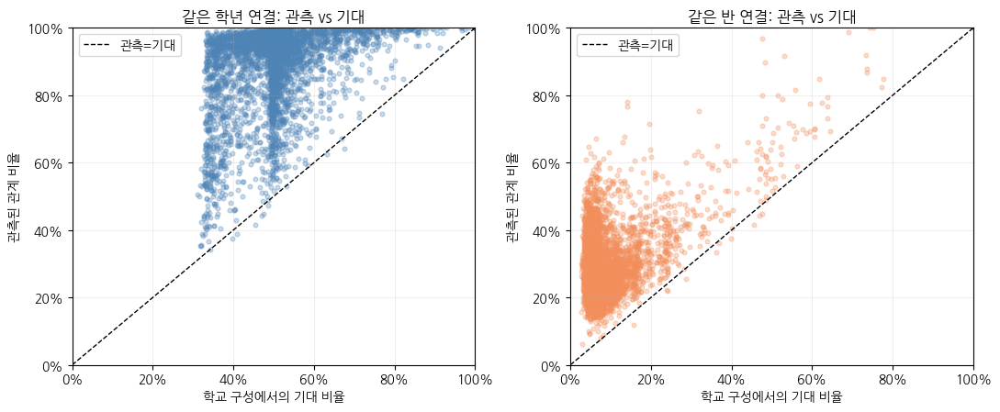

In [ ]:
# 학교 구성 대비 동일 학년·반 연결
homophily=network_con.execute('''
WITH roster AS (
  SELECT school_id,
         COUNT(*) AS n_users,
         COUNT(current_grade) AS grade_known_users,
         COUNT(CASE WHEN current_grade IS NOT NULL AND current_class_num IS NOT NULL THEN 1 END) AS class_known_users
  FROM graph_nodes GROUP BY 1
), grade_group AS (
  SELECT school_id,current_grade,COUNT(*) AS n
  FROM graph_nodes WHERE current_grade IS NOT NULL GROUP BY 1,2
), class_group AS (
  SELECT school_id,current_grade,current_class_num,COUNT(*) AS n
  FROM graph_nodes
  WHERE current_grade IS NOT NULL AND current_class_num IS NOT NULL GROUP BY 1,2,3
), expected AS (
  SELECT r.school_id,r.n_users,r.grade_known_users,r.class_known_users,
         CASE WHEN r.grade_known_users>1 THEN
           (SELECT SUM(g.n*(g.n-1)) FROM grade_group g WHERE g.school_id=r.school_id)/
           (r.grade_known_users*(r.grade_known_users-1.0)) END AS expected_same_grade_share,
         CASE WHEN r.class_known_users>1 THEN
           (SELECT SUM(c.n*(c.n-1)) FROM class_group c WHERE c.school_id=r.school_id)/
           (r.class_known_users*(r.class_known_users-1.0)) END AS expected_same_class_share
  FROM roster r
), edge_relation AS (
  SELECT e.school_id,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL THEN 1 ELSE 0 END AS grade_known,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL
                   AND a.current_grade=b.current_grade THEN 1 ELSE 0 END AS same_grade,
         CASE WHEN a.current_grade IS NOT NULL AND b.current_grade IS NOT NULL
                   AND a.current_class_num IS NOT NULL AND b.current_class_num IS NOT NULL THEN 1 ELSE 0 END AS class_known,
         CASE WHEN a.current_grade=b.current_grade AND a.current_class_num=b.current_class_num
                   AND a.current_grade IS NOT NULL AND a.current_class_num IS NOT NULL
                   AND b.current_grade IS NOT NULL AND b.current_class_num IS NOT NULL THEN 1 ELSE 0 END AS same_class
  FROM accepted_school_edges e
  JOIN graph_nodes a ON a.node_idx=e.u_idx
  JOIN graph_nodes b ON b.node_idx=e.v_idx
), observed AS (
  SELECT school_id,COUNT(*) AS accepted_edges,
         SUM(grade_known) AS grade_known_edges,SUM(same_grade) AS same_grade_edges,
         SUM(class_known) AS class_known_edges,SUM(same_class) AS same_class_edges
  FROM edge_relation GROUP BY 1
)
SELECT e.*,o.accepted_edges,o.grade_known_edges,o.same_grade_edges,o.class_known_edges,o.same_class_edges,
       o.same_grade_edges/NULLIF(o.grade_known_edges,0.0) AS observed_same_grade_share,
       o.same_class_edges/NULLIF(o.class_known_edges,0.0) AS observed_same_class_share
FROM expected e LEFT JOIN observed o USING(school_id)
''').fetchdf()
homophily["same_grade_excess_pp"]=100*(homophily.observed_same_grade_share-homophily.expected_same_grade_share)
homophily["same_class_excess_pp"]=100*(homophily.observed_same_class_share-homophily.expected_same_class_share)
homophily["same_grade_lift"]=homophily.observed_same_grade_share/homophily.expected_same_grade_share.replace(0,np.nan)
homophily["same_class_lift"]=homophily.observed_same_class_share/homophily.expected_same_class_share.replace(0,np.nan)
homophily["cross_class_bridge_share"]=1-homophily.observed_same_class_share

homophily_tests=[]
for level,min_edges in [("grade",30),("class",30)]:
    z=homophily[(homophily[f"{level}_known_edges"]>=min_edges) &
                homophily[f"observed_same_{level}_share"].notna() &
                homophily[f"expected_same_{level}_share"].notna()].copy()
    diff=(z[f"observed_same_{level}_share"]-z[f"expected_same_{level}_share"]).to_numpy()
    nz=diff[diff!=0]
    stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
    homophily_tests.append({"level":level,"schools":len(z),"minimum_known_edges":min_edges,
                            "median_observed_share":z[f"observed_same_{level}_share"].median(),
                            "median_expected_share":z[f"expected_same_{level}_share"].median(),
                            "median_excess_pp":100*np.median(diff) if len(diff) else np.nan,
                            "share_above_expected":np.mean(diff>0) if len(diff) else np.nan,
                            "wilcoxon_p":p})
homophily_tests=pd.DataFrame(homophily_tests)
display(homophily_tests.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
for ax,level,color in [(axes[0],"grade",COLORS["blue"]),(axes[1],"class",COLORS["orange"])]:
    z=homophily[homophily[f"{level}_known_edges"]>=30]
    ax.scatter(z[f"expected_same_{level}_share"],z[f"observed_same_{level}_share"],s=12,alpha=.3,color=color)
    ax.plot([0,1],[0,1],color="black",ls="--",lw=1,label="관측=기대")
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.legend(); ax.grid(alpha=.2)
    ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("학교 구성에서의 기대 비율"); ax.set_ylabel("관측된 관계 비율")
    ax.set_title(f"같은 {'학년' if level=='grade' else '반'} 연결: 관측 vs 기대")
plt.tight_layout()
plt.show()

plt.close('all')


- 조건을 충족한 4,293개 학교에서 같은 학년 연결 비중의 중앙값은 92.73%, 학교 구성상 기대값은 49.90%다.
- 같은 반 연결도 관측 27.30%, 기대 6.96%로 현재 같은 학년·반에 속한 사용자끼리 연결이 집중됐다.


,metric,comparison,schools,median_before,median_after,median_difference,share_increased,wilcoxon_p
0,active_user_share,pre->early,3634,0.8750,0.9434,0.0453,0.6370,0.0000
1,active_user_share,early->late,3792,0.9439,0.5432,-0.3694,0.0200,0.0000
2,isolate_share,pre->early,3634,0.1250,0.0566,-0.0453,0.3594,0.0000
3,isolate_share,early->late,3792,0.0561,0.4568,0.3694,0.9773,0.0000
4,average_degree,pre->early,3634,4.3288,19.9956,14.9093,0.8861,0.0000
5,average_degree,early->late,3792,20.3179,1.8732,-17.4458,0.0229,0.0000
6,density,pre->early,3539,0.2000,0.1369,-0.0610,0.2809,0.0000
7,density,early->late,3792,0.1398,0.0120,-0.1212,0.0166,0.0000
8,largest_component_share,pre->early,3634,0.8571,0.9419,0.0535,0.6395,0.0000
9,largest_component_share,early->late,3792,0.9425,0.5250,-0.3818,0.0211,0.0000


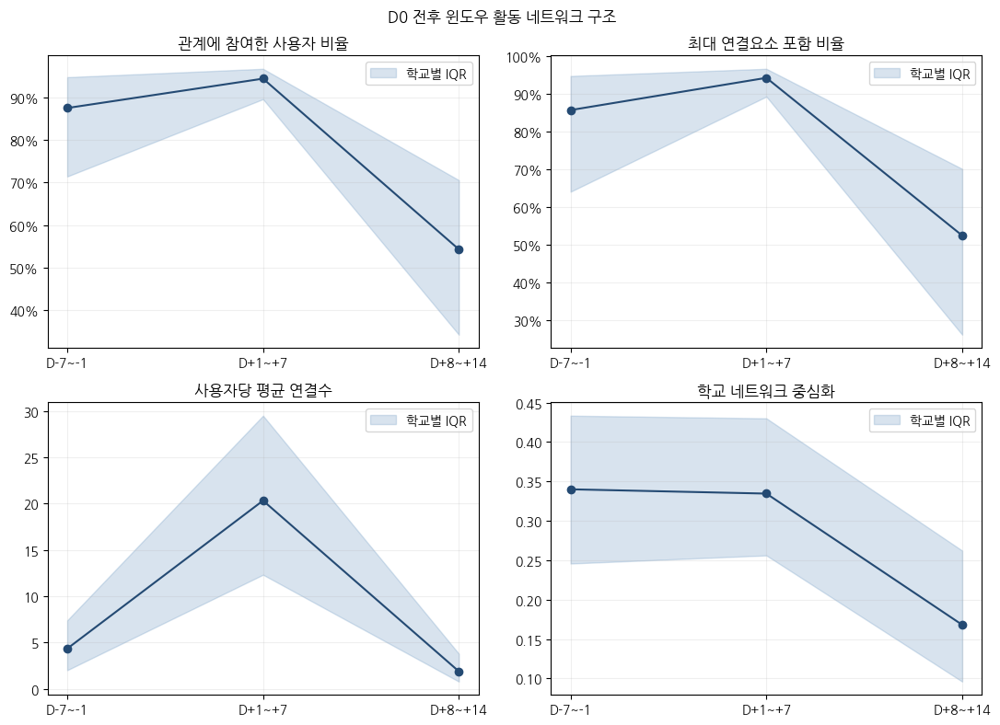

In [ ]:
# D0 구간별 최종 수락 요청 관계망 비교
valid_d0_school_df=pd.DataFrame({"school_id":pd.Series(school_event.school_id.unique(),dtype="int64")})
network_con.register("valid_d0_school_df",valid_d0_school_df)
network_con.execute('''
CREATE OR REPLACE TEMP TABLE d0_complete_school AS
SELECT v.school_id,
       MAX(TRY_CAST(s.current_roster_40th_signup_at AS TIMESTAMP)) AS d0_at
FROM valid_d0_school_df v
JOIN school_daily s USING(school_id)
GROUP BY 1
''')

network_con.execute('''
CREATE OR REPLACE TEMP TABLE phase_accepted_edges AS
WITH base AS (
  SELECT n1.school_id,n1.node_idx AS send_idx,n2.node_idx AS receive_idx,
         DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) AS rel_day
  FROM event e
  JOIN graph_nodes n1 ON n1.user_id=e.send_user_id
  JOIN graph_nodes n2 ON n2.user_id=e.receive_user_id
  JOIN d0_complete_school d ON d.school_id=n1.school_id
  WHERE e.analysis_eligible_request_flag=1
    AND e.same_school_current_flag=1
    AND e.final_status_code='A'
    AND n1.school_id=n2.school_id
)
SELECT DISTINCT school_id,
       CASE WHEN rel_day BETWEEN -7 AND -1 THEN 'pre'
            WHEN rel_day BETWEEN 1 AND 7 THEN 'early'
            WHEN rel_day BETWEEN 8 AND 14 THEN 'late' END AS phase,
       LEAST(send_idx,receive_idx)::INTEGER AS u_idx,
       GREATEST(send_idx,receive_idx)::INTEGER AS v_idx
FROM base
WHERE rel_day BETWEEN -7 AND 14 AND rel_day<>0 AND send_idx<>receive_idx
''')

phase_reciprocity=network_con.execute('''
WITH base AS (
  SELECT DISTINCT n1.school_id,
         CASE WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN -7 AND -1 THEN 'pre'
              WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN 1 AND 7 THEN 'early'
              WHEN DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN 8 AND 14 THEN 'late' END AS phase,
         e.send_user_id,e.receive_user_id
  FROM event e
  JOIN graph_nodes n1 ON n1.user_id=e.send_user_id
  JOIN graph_nodes n2 ON n2.user_id=e.receive_user_id
  JOIN d0_complete_school d ON d.school_id=n1.school_id
  WHERE e.analysis_eligible_request_flag=1
    AND e.same_school_current_flag=1
    AND e.final_status_code='A'
    AND n1.school_id=n2.school_id
    AND DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE)) BETWEEN -7 AND 14
    AND DATE_DIFF('day',CAST(d.d0_at AS DATE),CAST(e.request_created_at_raw AS DATE))<>0
), canonical AS (
  SELECT school_id,phase,LEAST(send_user_id,receive_user_id) AS user_a,
         GREATEST(send_user_id,receive_user_id) AS user_b,COUNT(*) AS direction_count
  FROM base WHERE phase IS NOT NULL GROUP BY 1,2,3,4
)
SELECT school_id,phase,COUNT(*) AS accepted_pair_count,
       SUM(direction_count=2)::BIGINT AS reciprocal_pair_count,
       SUM(direction_count=2)/COUNT(*)::DOUBLE AS reciprocal_pair_share
FROM canonical GROUP BY 1,2
''').fetchdf()

phase_edge_np=network_con.execute('''
SELECT CASE phase WHEN 'pre' THEN 0 WHEN 'early' THEN 1 ELSE 2 END::INTEGER AS phase_code,
       u_idx,v_idx
FROM phase_accepted_edges
ORDER BY phase_code,u_idx,v_idx
''').fetchnumpy()
phase_edges=pd.DataFrame({
    "phase_code":phase_edge_np["phase_code"].astype(np.int8,copy=False),
    "u_idx":phase_edge_np["u_idx"].astype(np.int32,copy=False),
    "v_idx":phase_edge_np["v_idx"].astype(np.int32,copy=False),
})
del phase_edge_np

d0_lookup=network_con.execute('SELECT school_id,d0_at FROM d0_complete_school').fetchdf()
d0_lookup["d0_at"]=pd.to_datetime(d0_lookup.d0_at)
node_phase_base=node_graph[["node_idx","school_id","signup_at"]].copy()
node_phase_base["signup_at"]=pd.to_datetime(node_phase_base.signup_at)
node_phase_base=node_phase_base.merge(d0_lookup,on="school_id",how="inner")

phase_meta={"pre":(0,-1),"early":(1,7),"late":(2,14)}
phase_structure_parts=[]
for phase,(phase_code,end_day) in phase_meta.items():
    pe=phase_edges[phase_edges.phase_code.eq(phase_code)]
    pu=pe.u_idx.to_numpy(np.int32,copy=False); pv=pe.v_idx.to_numpy(np.int32,copy=False)
    prow=np.concatenate([pu,pv]); pcol=np.concatenate([pv,pu])
    padj=sparse.csr_matrix((np.ones(len(prow),dtype=np.uint8),(prow,pcol)),shape=(n_nodes,n_nodes))
    padj.sum_duplicates(); padj.data[:]=1
    _,plabel=connected_components(padj,directed=False,return_labels=True)
    pdegree=np.diff(padj.indptr).astype(np.int32)

    eligible=node_phase_base.signup_at.notna() & (
        node_phase_base.signup_at.dt.normalize() <=
        (node_phase_base.d0_at+pd.to_timedelta(end_day,unit="D")).dt.normalize())
    pn=node_phase_base.loc[eligible,["node_idx","school_id"]].copy()
    idx=pn.node_idx.to_numpy(np.int32,copy=False)
    pn["degree"]=pdegree[idx]
    pn["component_label"]=plabel[idx]
    pn["active"]=(pn.degree>0).astype(int)

    pcs=(pn.groupby(["school_id","component_label"],as_index=False).size()
         .rename(columns={"size":"component_size"}))
    p_lcc=(pcs.groupby("school_id",as_index=False).component_size.max()
           .rename(columns={"component_size":"largest_component_users"}))
    p_components=(pcs.groupby("school_id",as_index=False).size()
                  .rename(columns={"size":"component_count"}))
    ps=(pn.groupby("school_id",as_index=False)
        .agg(eligible_users=("node_idx","size"),active_users=("active","sum"),
             total_degree=("degree","sum"),max_degree=("degree","max")))
    ps=ps.merge(p_lcc,on="school_id",how="left").merge(p_components,on="school_id",how="left")
    ps["phase"]=phase
    ps["accepted_edge_count"]=(ps.total_degree//2).astype(np.int64)
    ps["active_user_share"]=ps.active_users/ps.eligible_users
    ps["isolate_share"]=1-ps.active_user_share
    ps["average_degree"]=ps.total_degree/ps.eligible_users
    ps["density"]=np.where(ps.eligible_users>1,ps.total_degree/(ps.eligible_users*(ps.eligible_users-1)),np.nan)
    ps["largest_component_share"]=ps.largest_component_users/ps.eligible_users
    ps["degree_centralization"]=np.where(
        ps.eligible_users>2,
        (ps.eligible_users*ps.max_degree-ps.total_degree)/
        ((ps.eligible_users-1)*(ps.eligible_users-2)),np.nan)
    phase_structure_parts.append(ps)
    del padj,plabel,pdegree,prow,pcol,pn,pcs

phase_structure=pd.concat(phase_structure_parts,ignore_index=True)
phase_structure=phase_structure.merge(phase_reciprocity,on=["school_id","phase"],how="left")
phase_structure[["accepted_pair_count","reciprocal_pair_count","reciprocal_pair_share"]]=(
    phase_structure[["accepted_pair_count","reciprocal_pair_count","reciprocal_pair_share"]].fillna(0))

phase_tests=[]
for metric in ["active_user_share","isolate_share","average_degree","density",
               "largest_component_share","degree_centralization","reciprocal_pair_share"]:
    wide=phase_structure.pivot(index="school_id",columns="phase",values=metric)
    for before,after in [("pre","early"),("early","late")]:
        z=wide[[before,after]].dropna()
        diff=(z[after]-z[before]).to_numpy(); nz=diff[diff!=0]
        stat,p=stats.wilcoxon(nz) if len(nz) else (np.nan,np.nan)
        phase_tests.append({"metric":metric,"comparison":f"{before}->{after}","schools":len(z),
                            "median_before":z[before].median(),"median_after":z[after].median(),
                            "median_difference":np.median(diff) if len(diff) else np.nan,
                            "share_increased":np.mean(diff>0) if len(diff) else np.nan,
                            "wilcoxon_p":p})
phase_structure_tests=pd.DataFrame(phase_tests)
display(phase_structure_tests.round(4))

phase_order=["pre","early","late"]
fig,axes=plt.subplots(2,2,figsize=(11,8))
for ax,(metric,title,percent) in zip(axes.ravel(),[
    ("active_user_share","관계에 참여한 사용자 비율",True),
    ("largest_component_share","최대 연결요소 포함 비율",True),
    ("average_degree","사용자당 평균 연결수",False),
    ("degree_centralization","학교 네트워크 중심화",False)]):
    summary=(phase_structure.groupby("phase")[metric]
             .agg(median="median",q25=lambda x:x.quantile(.25),q75=lambda x:x.quantile(.75))
             .reindex(phase_order))
    x=np.arange(3)
    ax.plot(x,summary["median"],marker="o",color=COLORS["navy"])
    ax.fill_between(x,summary.q25,summary.q75,color=COLORS["blue"],alpha=.22,label="학교별 IQR")
    ax.set_xticks(x,["D-7~-1","D+1~+7","D+8~+14"]); ax.set_title(title); ax.grid(alpha=.2); ax.legend()
    if percent: ax.yaxis.set_major_formatter(PercentFormatter(1))
plt.suptitle("D0 전후 윈도우 활동 네트워크 구조")
plt.tight_layout()
plt.show()

plt.close('all')


- 구간별 최종 수락 관계망에서 연결이 있는 사용자 비율의 학교 중앙값은 첫째 주 94.39%에서 둘째 주 54.32%로 낮아졌다.
- 평균 연결 수의 학교 중앙값도 20.32개에서 1.87개로 낮아졌다. 여기서 연결은 각 구간에 생성되고 최종 수락된 요청쌍이다.


,size_quantile,school_id,n_users,edge_count,component_count,largest_component_users,max_core,max_degree,betweenness_sources
0,Q25,132,100,1330,5,96,23,60,32
1,Q50,12,154,2872,4,151,29,108,32
2,Q75,216,225,6231,5,221,47,168,32


,size_quantile,school_id,node_alias,degree,degree_centrality,sampled_betweenness,eigenvector_centrality,core_number,in_largest_component_flag
41,Q25,132,Q25_node_001,60.0,0.606061,0.045109,1.000000,23,1
26,Q25,132,Q25_node_002,57.0,0.575758,0.049413,0.887279,23,1
4,Q25,132,Q25_node_004,53.0,0.535354,0.032721,0.916869,23,1
44,Q25,132,Q25_node_003,53.0,0.535354,0.021976,0.967601,23,1
6,Q25,132,Q25_node_005,51.0,0.515152,0.030315,0.792715,23,1
100,Q50,12,Q50_node_001,108.0,0.705882,0.085406,1.000000,29,1
218,Q50,12,Q50_node_002,90.0,0.588235,0.056711,0.836078,29,1
106,Q50,12,Q50_node_003,88.0,0.575163,0.059326,0.815167,29,1
133,Q50,12,Q50_node_004,86.0,0.562092,0.044707,0.838480,29,1
123,Q50,12,Q50_node_005,80.0,0.522876,0.032149,0.750388,29,1


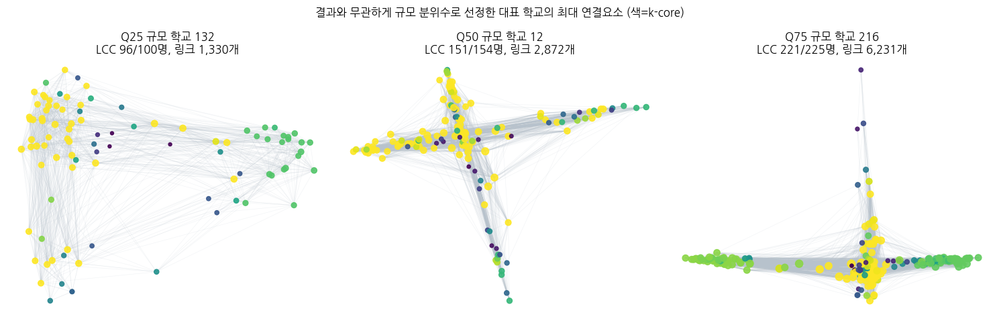

In [ ]:
# 학교 규모별 대표 관계망·중심성·코어
def core_numbers_from_csr(a):
    deg=np.diff(a.indptr).astype(int)
    current=deg.copy(); removed=np.zeros(a.shape[0],dtype=bool); core=np.zeros(a.shape[0],dtype=int)
    heap=[(int(d),int(i)) for i,d in enumerate(current)]; heapq.heapify(heap)
    while heap:
        d,v=heapq.heappop(heap)
        if removed[v] or d!=current[v]:
            continue
        removed[v]=True; core[v]=d
        for u in a.indices[a.indptr[v]:a.indptr[v+1]]:
            if not removed[u] and current[u]>d:
                current[u]-=1; heapq.heappush(heap,(int(current[u]),int(u)))
    return core

def sampled_betweenness_from_csr(a,max_sources=32):
    n=a.shape[0]; score=np.zeros(n,dtype=float)
    if n<3: return score
    sources=np.unique(np.linspace(0,n-1,min(max_sources,n),dtype=int))
    for s in sources:
        stack=[]; pred=[[] for _ in range(n)]; sigma=np.zeros(n); sigma[s]=1
        dist=np.full(n,-1,dtype=int); dist[s]=0; q=deque([int(s)])
        while q:
            v=q.popleft(); stack.append(v)
            for w in a.indices[a.indptr[v]:a.indptr[v+1]]:
                if dist[w]<0:
                    dist[w]=dist[v]+1; q.append(int(w))
                if dist[w]==dist[v]+1:
                    sigma[w]+=sigma[v]; pred[w].append(v)
        delta=np.zeros(n)
        while stack:
            w=stack.pop()
            if sigma[w]>0:
                coeff=(1+delta[w])/sigma[w]
                for v in pred[w]: delta[v]+=sigma[v]*coeff
            if w!=s: score[w]+=delta[w]
    score*=n/len(sources)
    score/=((n-1)*(n-2))
    return score

eligible_rep=school_structure[(school_structure.n_users>=40)&(school_structure.accepted_edge_count>0)].copy()
size_targets=eligible_rep.n_users.quantile([.25,.5,.75]).to_dict()
chosen=[]
for quantile,target in size_targets.items():
    remaining=eligible_rep[~eligible_rep.school_id.isin(chosen)]
    sid=int(remaining.loc[(remaining.n_users-target).abs().idxmin(),"school_id"])
    chosen.append(sid)

representative_rows=[]; centrality_node_rows=[]; representative_graphs=[]
for quantile,sid in zip(["Q25","Q50","Q75"],chosen):
    global_idx=node_graph.loc[node_graph.school_id.eq(sid),"node_idx"].to_numpy(np.int32)
    a=accepted_adj[global_idx,:][:,global_idx].tocsr()
    degree=np.diff(a.indptr).astype(float)
    degree_c=degree/max(len(degree)-1,1)
    core=core_numbers_from_csr(a)
    between=sampled_betweenness_from_csr(a,max_sources=32)
    eigen=np.zeros(len(degree),dtype=float)
    if len(degree)>2 and a.nnz>0:
        try:
            _,vec=eigsh(a.astype(float),k=1,which="LA",tol=1e-3,maxiter=3000)
            eigen=np.abs(vec[:,0]); eigen/=eigen.max() if eigen.max()>0 else 1
        except Exception:
            eigen=degree_c.copy()
    ncomp,clabel=connected_components(a,directed=False,return_labels=True)
    counts=np.bincount(clabel); lcc_label=int(np.argmax(counts)); lcc_local=np.where(clabel==lcc_label)[0]
    representative_rows.append({"size_quantile":quantile,"school_id":sid,"n_users":len(degree),
                                "edge_count":int(a.nnz//2),"component_count":ncomp,
                                "largest_component_users":int(counts[lcc_label]),
                                "max_core":int(core.max()) if len(core) else 0,
                                "max_degree":int(degree.max()) if len(degree) else 0,
                                "betweenness_sources":min(32,len(degree))})
    rank_order=np.argsort(-degree)
    rank_map=np.empty(len(degree),dtype=int); rank_map[rank_order]=np.arange(1,len(degree)+1)
    for i in range(len(degree)):
        centrality_node_rows.append({"size_quantile":quantile,"school_id":sid,
                                     "node_alias":f"{quantile}_node_{rank_map[i]:03d}",
                                     "degree":degree[i],"degree_centrality":degree_c[i],
                                     "sampled_betweenness":between[i],"eigenvector_centrality":eigen[i],
                                     "core_number":core[i],"in_largest_component_flag":int(clabel[i]==lcc_label)})
    representative_graphs.append((quantile,sid,a,degree,core,lcc_local))

representative_summary=pd.DataFrame(representative_rows)
representative_centrality=pd.DataFrame(centrality_node_rows)
display(representative_summary)
display(representative_centrality.sort_values(["size_quantile","degree"],ascending=[True,False]).groupby("size_quantile").head(5))

fig,axes=plt.subplots(1,3,figsize=(15,4.8))
for ax,(quantile,sid,a,degree,core,lcc_local) in zip(axes,representative_graphs):
    af=a[lcc_local,:][:,lcc_local].tocsr(); m=af.shape[0]
    if m>=3 and af.nnz>0:
        try:
            lap=sparse.csgraph.laplacian(af.astype(float),normed=True)
            k=min(3,m-1)
            _,vec=eigsh(lap,k=k,which="SM",tol=1e-3,maxiter=3000)
            pos=np.column_stack([vec[:,1] if k>1 else np.arange(m),vec[:,2] if k>2 else np.zeros(m)])
        except Exception:
            theta=np.linspace(0,2*np.pi,m,endpoint=False); pos=np.column_stack([np.cos(theta),np.sin(theta)])
    else:
        theta=np.linspace(0,2*np.pi,max(m,1),endpoint=False); pos=np.column_stack([np.cos(theta),np.sin(theta)])[:m]
    rr,cc=sparse.triu(af,k=1).nonzero()
    for u,v in zip(rr,cc):
        ax.plot(pos[[u,v],0],pos[[u,v],1],color="#B7C2CC",alpha=.18,lw=.45,zorder=1)
    local_degree=degree[lcc_local]; local_core=core[lcc_local]
    sc=ax.scatter(pos[:,0],pos[:,1],s=8+5*np.sqrt(local_degree),c=local_core,cmap="viridis",alpha=.9,zorder=2)
    ax.set_title(f"{quantile} 규모 학교 {sid}\nLCC {m}/{len(degree)}명, 링크 {a.nnz//2:,}개")
    ax.axis("off")
plt.suptitle("결과와 무관하게 규모 분위수로 선정한 대표 학교의 최대 연결요소 (색=k-core)")
plt.tight_layout()
plt.show()

plt.close('all')


- 규모 25%·50%·75% 지점의 대표 학교는 100명·154명·225명이며, 최대 연결 집단은 96명·151명·221명이다. 최대 코어 수는 각각 23·29·47로 내부 연결 정도에 차이가 있었다.
- 세 학교의 사례이고, 매개 중심성은 32개 출발점으로 계산한 근삿값이다.


### 3-2-9. 관계망 구조의 설명 범위와 검증

- 구조 지표를 추가했을 때 후기 활동 예측이 나아지는지 살펴본다.
- 최종 수락만 포함한 관계망과 전체 요청을 포함한 관계망을 비교한다. 최종 상태를 사용하는 데 따른 미래정보 문제는 별도로 남는다.


,model,train_schools,test_schools,test_r2,test_mae_log_scale,selected_alpha
0,요청량 기준 모델,3033,759,-1.9706,1.7610,13.4340
1,구조 지표 추가 모델,3033,759,-1.4160,1.5329,2.0309


,early_structure_metric,schools,spearman_rho_with_late_activity,p_value
0,early_structure_active_user_share,3792,0.2899,0.0
1,early_structure_average_degree,3792,0.2764,0.0
2,early_structure_largest_component_share,3792,0.2831,0.0
3,early_structure_degree_centralization,3792,0.1102,0.0
4,early_structure_reciprocal_pair_share,3792,0.1053,0.0


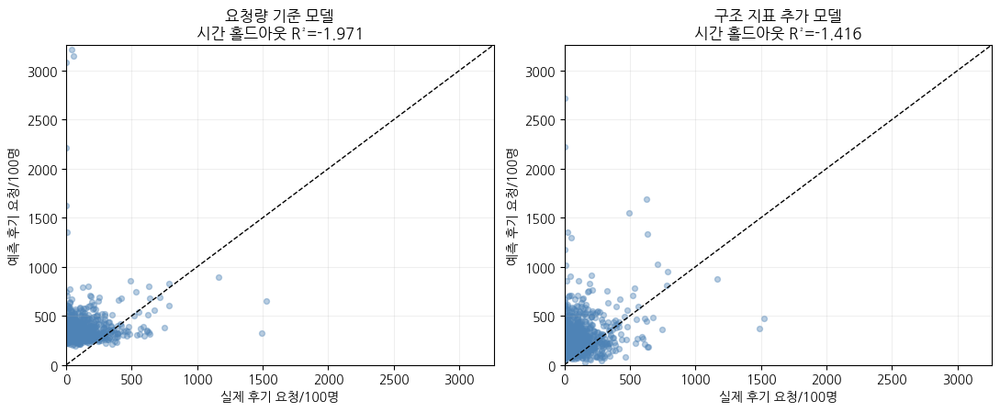

In [ ]:
# 초기 관계망 구조 추가 모델·시간 검증
early_structure=(phase_structure[phase_structure.phase.eq("early")]
                 [["school_id","active_user_share","isolate_share","average_degree","density",
                   "largest_component_share","degree_centralization","reciprocal_pair_share"]]
                 .rename(columns=lambda c: c if c=="school_id" else f"early_structure_{c}"))
structure_model=model_df.merge(early_structure,on="school_id",how="inner").copy()
baseline_features=["log_roster_size","d0_day_index","early_new_users_per_100","early_requests_per_100"]
structure_features=["early_structure_active_user_share","early_structure_average_degree",
                    "early_structure_largest_component_share","early_structure_degree_centralization",
                    "early_structure_reciprocal_pair_share"]
target="log_late_request_rate"
network_structure_sample=structure_model.dropna(subset=baseline_features+structure_features+[target]).sort_values("d0_date").copy()
split=int(len(network_structure_sample)*.8); train=np.arange(len(network_structure_sample))<split; test=~train
structure_model_rows=[]; structure_predictions=[]; fitted_models={}
for label,cols in [("요청량 기준 모델",baseline_features),("구조 지표 추가 모델",baseline_features+structure_features)]:
    pipe=make_pipeline(StandardScaler(),RidgeCV(alphas=np.logspace(-4,4,40)))
    pipe.fit(network_structure_sample.loc[train,cols],network_structure_sample.loc[train,target])
    pred=pipe.predict(network_structure_sample.loc[test,cols]); fitted_models[label]=(pipe,cols,pred)
    structure_model_rows.append({"model":label,"train_schools":int(train.sum()),"test_schools":int(test.sum()),
                                 "test_r2":r2_score(network_structure_sample.loc[test,target],pred),
                                 "test_mae_log_scale":mean_absolute_error(network_structure_sample.loc[test,target],pred),
                                 "selected_alpha":pipe.named_steps["ridgecv"].alpha_})
    for sid,actual,predicted in zip(network_structure_sample.loc[test,"school_id"],network_structure_sample.loc[test,target],pred):
        structure_predictions.append({"model":label,"school_id":sid,
                                      "actual_late_requests_per_100":np.expm1(actual),
                                      "predicted_late_requests_per_100":np.expm1(predicted)})
structure_model_quality=pd.DataFrame(structure_model_rows)
structure_model_predictions=pd.DataFrame(structure_predictions)

structure_correlations=[]
for col in structure_features:
    rho,p=stats.spearmanr(network_structure_sample[col],network_structure_sample[target],nan_policy="omit")
    structure_correlations.append({"early_structure_metric":col,"schools":len(network_structure_sample),
                                   "spearman_rho_with_late_activity":rho,"p_value":p})
structure_correlations=pd.DataFrame(structure_correlations)
display(structure_model_quality.round(4)); display(structure_correlations.round(4))

fig,axes=plt.subplots(1,2,figsize=(11,4.6))
lim=max(structure_model_predictions.actual_late_requests_per_100.quantile(.98),
        structure_model_predictions.predicted_late_requests_per_100.quantile(.98))
for ax,label in zip(axes,["요청량 기준 모델","구조 지표 추가 모델"]):
    z=structure_model_predictions[structure_model_predictions.model.eq(label)]
    ax.scatter(z.actual_late_requests_per_100,z.predicted_late_requests_per_100,s=18,alpha=.4,color=COLORS["blue"])
    ax.plot([0,lim],[0,lim],color="black",ls="--",lw=1)
    q=structure_model_quality[structure_model_quality.model.eq(label)].iloc[0]
    ax.set_xlim(0,lim); ax.set_ylim(0,lim); ax.grid(alpha=.2)
    ax.set_xlabel("실제 후기 요청/100명"); ax.set_ylabel("예측 후기 요청/100명")
    ax.set_title(f"{label}\n시간 홀드아웃 R²={q.test_r2:.3f}")
plt.tight_layout()
plt.show()

plt.close('all')


- 나중에 도달한 학교에서 요청량 기준 모델의 R²는 -1.9706, 구조 지표 추가 모델은 -1.4160이다.
- 구조를 추가하며 오차는 줄었지만 둘 다 검증 집단 평균으로 예측하는 것보다 못했다. 후기 활동을 안정적으로 예측하기에는 부족하다.


,accepted_metric,all_request_metric,schools,accepted_median,all_request_median,spearman_rho,p_value
0,active_user_share,all_request_active_user_share,3897,0.9671,0.9958,0.4648,0.0
1,average_degree,all_request_average_degree,3897,28.7303,37.6589,0.9751,0.0
2,density,all_request_density,3897,0.1802,0.2444,0.9692,0.0


,check,value,expected,pass_flag,explanation,status
0,학교 구조표 school_id 유일성,0,0,1,,PASS
1,노드 수 보존,677080,677080,1,,PASS
2,링크 수 보존,10377675,10377675,1,,PASS
3,활성 비율 범위 오류,0,0,1,,PASS
4,LCC 비율 범위 오류,0,0,1,,PASS
5,D0 구간 학교 중복,0,0,1,,PASS
6,구조 예측 미래정보 사용,미검증,최종 수락 확정 시각 필요,<NA>,요청 생성 구간은 나눴지만 최종 수락 상태가 D+7에 확정됐는지는 알 수 없음,NOT_VERIFIED


구조 검증: PASS 6 / FAIL 0 / NOT_VERIFIED 1


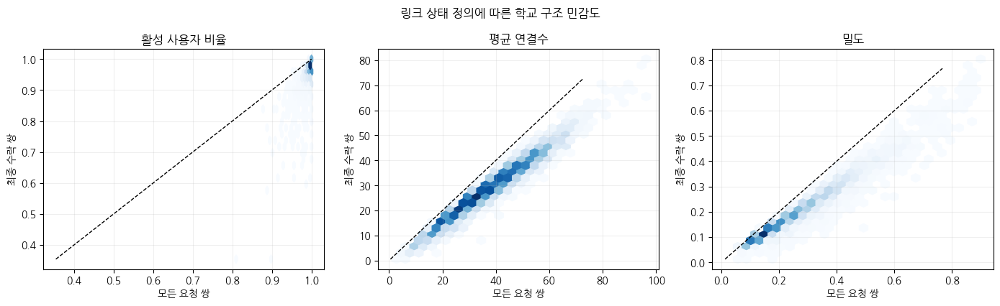

In [ ]:
# 최종 수락·전체 요청 정의 비교와 구조 검증
all_request_structure=network_con.execute('''
WITH canonical AS (
  SELECT DISTINCT ns.school_id,
         LEAST(ns.node_idx,nr.node_idx) AS u_idx,
         GREATEST(ns.node_idx,nr.node_idx) AS v_idx
  FROM pair p
  JOIN graph_nodes ns ON ns.user_id=p.send_user_id
  JOIN graph_nodes nr ON nr.user_id=p.receive_user_id
  WHERE p.analysis_eligible_pair_flag=1 AND p.same_school_current_flag=1
    AND ns.school_id=nr.school_id AND ns.node_idx<>nr.node_idx
), active AS (
  SELECT school_id,u_idx AS node_idx FROM canonical
  UNION
  SELECT school_id,v_idx AS node_idx FROM canonical
), edges AS (
  SELECT school_id,COUNT(*) AS all_request_edge_count FROM canonical GROUP BY 1
), active_count AS (
  SELECT school_id,COUNT(*) AS all_request_active_users FROM active GROUP BY 1
)
SELECT n.school_id,COUNT(*) AS n_users,
       COALESCE(MAX(e.all_request_edge_count),0) AS all_request_edge_count,
       COALESCE(MAX(a.all_request_active_users),0) AS all_request_active_users
FROM graph_nodes n
LEFT JOIN edges e USING(school_id)
LEFT JOIN active_count a USING(school_id)
GROUP BY 1
''').fetchdf()
all_request_structure["all_request_active_user_share"]=all_request_structure.all_request_active_users/all_request_structure.n_users
all_request_structure["all_request_average_degree"]=2*all_request_structure.all_request_edge_count/all_request_structure.n_users
all_request_structure["all_request_density"]=np.where(
    all_request_structure.n_users>1,
    2*all_request_structure.all_request_edge_count/(all_request_structure.n_users*(all_request_structure.n_users-1)),np.nan)

robustness=school_structure[["school_id","n_users","accepted_edge_count","active_user_share","average_degree","density"]].merge(
    all_request_structure,on=["school_id","n_users"],how="left")
robustness_tests=[]
z=robustness[robustness.n_users>=40].copy()
for accepted_col,all_col in [("active_user_share","all_request_active_user_share"),
                             ("average_degree","all_request_average_degree"),("density","all_request_density")]:
    rho,p=stats.spearmanr(z[accepted_col],z[all_col],nan_policy="omit")
    robustness_tests.append({"accepted_metric":accepted_col,"all_request_metric":all_col,"schools":len(z),
                             "accepted_median":z[accepted_col].median(),"all_request_median":z[all_col].median(),
                             "spearman_rho":rho,"p_value":p})
robustness_tests=pd.DataFrame(robustness_tests)

phase_wide=phase_structure.pivot(index="school_id",columns="phase",
                                 values=["eligible_users","accepted_edge_count","active_user_share",
                                         "average_degree","density","largest_component_share",
                                         "degree_centralization","reciprocal_pair_share"])
phase_wide.columns=[f"{metric}_{phase}" for metric,phase in phase_wide.columns]
phase_wide=phase_wide.reset_index()
school_network_master=(school_structure.merge(
    homophily.drop(columns=["n_users"],errors="ignore"),on="school_id",how="left",suffixes=("","_homophily"))
    .merge(phase_wide,on="school_id",how="left"))

structural_qa=pd.DataFrame([
  {"check":"학교 구조표 school_id 유일성","value":int(school_structure.school_id.duplicated().sum()),"expected":"0",
   "pass_flag":int(school_structure.school_id.duplicated().sum()==0)},
  {"check":"노드 수 보존","value":int(school_structure.n_users.sum()),"expected":str(n_nodes),
   "pass_flag":int(school_structure.n_users.sum()==n_nodes)},
  {"check":"링크 수 보존","value":int(school_structure.accepted_edge_count.sum()),"expected":str(len(edge_u)),
   "pass_flag":int(school_structure.accepted_edge_count.sum()==len(edge_u))},
  {"check":"활성 비율 범위 오류","value":int((~school_structure.active_user_share.between(0,1)).sum()),"expected":"0",
   "pass_flag":int(school_structure.active_user_share.between(0,1).all())},
  {"check":"LCC 비율 범위 오류","value":int((~school_structure.largest_component_share.between(0,1)).sum()),"expected":"0",
   "pass_flag":int(school_structure.largest_component_share.between(0,1).all())},
  {"check":"D0 구간 학교 중복","value":int(phase_structure.duplicated(["school_id","phase"]).sum()),"expected":"0",
   "pass_flag":int(phase_structure.duplicated(["school_id","phase"]).sum()==0)},
  {"check":"구조 예측 미래정보 사용","value":"미검증","expected":"최종 수락 확정 시각 필요",
   "pass_flag":pd.NA,"explanation":"요청 생성 구간은 나눴지만 최종 수락 상태가 D+7에 확정됐는지는 알 수 없음"},
])
structural_qa["status"] = structural_qa["pass_flag"].map({1: "PASS", 0: "FAIL"}).fillna("NOT_VERIFIED")
structural_qa["explanation"] = structural_qa["explanation"].fillna("")
structural_failures = structural_qa.loc[structural_qa["status"].eq("FAIL")]
assert structural_failures.empty, structural_failures
display(robustness_tests.round(4)); display(structural_qa)
print(
    f"구조 검증: PASS {structural_qa['status'].eq('PASS').sum()} / "
    f"FAIL {len(structural_failures)} / "
    f"NOT_VERIFIED {structural_qa['status'].eq('NOT_VERIFIED').sum()}"
)

fig,axes=plt.subplots(1,3,figsize=(14,4.3))
for ax,(accepted_col,all_col,title) in zip(axes,[
    ("active_user_share","all_request_active_user_share","활성 사용자 비율"),
    ("average_degree","all_request_average_degree","평균 연결수"),
    ("density","all_request_density","밀도")]):
    ax.hexbin(z[all_col],z[accepted_col],gridsize=28,mincnt=1,cmap="Blues")
    lo=min(z[all_col].min(),z[accepted_col].min()); hi=max(z[all_col].quantile(.99),z[accepted_col].quantile(.99))
    ax.plot([lo,hi],[lo,hi],color="black",ls="--",lw=1)
    ax.set_xlabel("모든 요청 쌍"); ax.set_ylabel("최종 수락 쌍"); ax.set_title(title); ax.grid(alpha=.2)
plt.suptitle("링크 상태 정의에 따른 학교 구조 민감도")
plt.tight_layout()
plt.show()

plt.close('all')


- 전체 요청을 포함하면 활성 비율 중앙값은 96.71%에서 99.58%, 평균 연결 수 중앙값은 28.73개에서 37.66개로 높아진다.
- 두 정의 사이의 학교 순위상관은 평균 연결 수 0.975, 밀도 0.969, 활성 비율 0.465다. 활성 비율이 연결 정의에 더 민감했다.
- 키·노드·링크 수와 지표 범위 검사는 통과했다. 최종 수락 상태의 확정 시각이 없어 미래정보 사용 여부는 `NOT_VERIFIED`로 남겼다.


In [ ]:
# 관계 진입·지속·구조 분석 요약
timing_sent=speed_summary.loc[speed_summary.metric.eq("가입→첫 요청 발송")].iloc[0]
timing_recv=speed_summary.loc[speed_summary.metric.eq("가입→첫 요청 수신")].iloc[0]
relation_test=quality_test.iloc[0]
pre_life=lifecycle_summary.set_index("signup_phase").loc["40명 이전 가입"]
post_life=lifecycle_summary.set_index("signup_phase").loc["40명 이후 가입"]
early_new_share=float(request_age_pooled[(request_age_pooled.phase.eq("early")) &
                                          (request_age_pooled.sender_age_band.eq("가입 24시간 이내"))]
                      .phase_request_share.iloc[0])
delay_phase=accepted_delay_overall.set_index("phase").median_delay_hours
q1=persistence_summary.iloc[0]; q5=persistence_summary.iloc[-1]
actual_placebo=placebo_tests[(placebo_tests.anchor_offset.eq(0)) &
                             (placebo_tests.metric.eq("requests_per_100"))].iloc[0]
later_placebo=placebo_tests[(placebo_tests.anchor_offset.eq(28)) &
                            (placebo_tests.metric.eq("requests_per_100"))].iloc[0]
structural_base=school_structure[school_structure.n_users>=40]
structural_medians=structural_base[["isolate_share","largest_component_share","average_degree",
                                    "degree_gini","degree_centralization"]].median()
early_active_test=phase_structure_tests[(phase_structure_tests.metric.eq("active_user_share")) &
                                        (phase_structure_tests.comparison.eq("pre->early"))].iloc[0]
late_active_test=phase_structure_tests[(phase_structure_tests.metric.eq("active_user_share")) &
                                       (phase_structure_tests.comparison.eq("early->late"))].iloc[0]
grade_homophily=homophily_tests[homophily_tests.level.eq("grade")].iloc[0]
class_homophily=homophily_tests[homophily_tests.level.eq("class")].iloc[0]
baseline_r2=structure_model_quality.loc[structure_model_quality.model.eq("요청량 기준 모델"),"test_r2"].iloc[0]
structure_r2=structure_model_quality.loc[structure_model_quality.model.eq("구조 지표 추가 모델"),"test_r2"].iloc[0]

findings=pd.DataFrame([
    {"판단":"가입 직후 관계 행동은 매우 빠르게 시작됨",
     "데이터 근거":f"첫 발송 중앙 {timing_sent.median_minutes:.2f}분, 첫 수신 중앙 {timing_recv.median_minutes:.2f}분",
     "해석":"가입자를 관계 화면까지 데려오는 초기 온보딩 동력은 강했다.",
     "제품 재설계 원칙":"첫 연결은 짧고 명확하게 유지하되 강제 발송량보다 실제 상호반응을 우선한다.",
     "성공 지표":"첫 요청까지 시간, 24시간 내 상대 반응 사용자율"},
    {"판단":"D0 직후 요청은 신규 가입자의 온보딩 행동에 크게 의존",
     "데이터 근거":f"D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중 {early_new_share:.1%}",
     "해석":"관계 활동 폭발의 상당 부분은 기존 사용자의 재활성화보다 신규 가입자의 첫날 행동이었다.",
     "제품 재설계 원칙":"가입 당일 행동과 재방문 관계 행동을 별도 루프로 설계한다.",
     "성공 지표":"가입 24시간 이내 요청 비중, 기존 사용자 관계 행동 비중"},
    {"판단":"40명 이후 가입자는 첫날에는 많이 보내지만 둘째 주 지속률은 낮음",
     "데이터 근거":f"첫 7일 발송자 중 D+8~D+14 지속 비율 {pre_life.d8_d14_continuation_share_among_early_senders:.1%}→{post_life.d8_d14_continuation_share_among_early_senders:.1%}; 첫 14일 발송 중 첫 24시간 집중 중앙값 {pre_life.median_first24_share_of_first14d:.1%}→{post_life.median_first24_share_of_first14d:.1%}",
     "해석":"동일한 가입 후 14일 창에서 비교해도 40명 이후 네트워크 경험은 더 강한 일회성 온보딩 버스트 형태였다.",
     "제품 재설계 원칙":"D+2~D+7에 새로운 관계 이유를 공급하는 두 번째 루프가 필요하다.",
     "성공 지표":"7일 이후 관계 행동 지속률, D+2~D+7 고유 상호작용자 수"},
    {"판단":"수신 과부하보다 관계에 이미 편입된 사용자에게 수락이 집중",
     "데이터 근거":f"요청 1건 수신자의 최종 수락 상태 비율 {receiver_test.accepted_share_at_1.iloc[0]:.1%}, 21~50건 수신자는 {receiver_test.accepted_share_at_21_50.iloc[0]:.1%}",
     "해석":"요청을 많이 받을수록 반응이 무너지는 과부하 패턴은 관측되지 않았다. 인기·활성도 선택효과일 수 있다.",
     "제품 재설계 원칙":"수신량 제한보다 관계가 적은 사용자의 첫 상호반응 실패를 우선 관리한다.",
     "성공 지표":"저연결 사용자 수락 상태 비율, 첫 상호 수락까지 시간"},
    {"판단":"초기 폭발 크기는 후기 절대 활동을 거의 구분하지 못함",
     "데이터 근거":f"초기 Q1 후기 중앙 {q1.late_request_rate_median:.1f}, Q5 후기 중앙 {q5.late_request_rate_median:.1f}; 초기-후기 Spearman ρ={persistence_test.spearman_early_vs_late_absolute.iloc[0]:.3f}",
     "해석":"초기에 훨씬 많이 보낸 학교도 2주차에는 비슷한 수준으로 수렴했다.",
     "제품 재설계 원칙":"초기 총요청량을 성공으로 보지 말고 후기 참여자 폭과 재상호작용을 관리한다.",
     "성공 지표":"D+8~D+14 고유 발송자율, 초기 대비 후기 관계 행동 유지"},
    {"판단":"D0 증가는 이후 임의 기준일에서 반복되지 않음",
     "데이터 근거":f"실제 D0 전후 요청률 중앙 변화 {actual_placebo.median_difference:.1f}, D+28 위약일은 {later_placebo.median_difference:.1f}",
     "해석":"D0 주변 관계 활동 변화가 단순한 아무 시점의 변동과 같지는 않았다. 다만 D0의 인과효과를 확정하지는 않는다.",
     "제품 재설계 원칙":"학교 활성화 시점을 운영 트리거로 활용하되 위약·달력 보정을 계속 병행한다.",
     "성공 지표":"활성화 전후 학교 보정 발송자율, 위약 대비 증분"},
    {"판단":"친구요청 수락 지연은 Viral Cycle Time이 아님",
     "데이터 근거":f"최종 수락 상태 갱신 지연 대리값: early 약 {delay_phase.get('early',np.nan):.1f}시간, late 약 {delay_phase.get('late',np.nan):.1f}시간",
     "해석":"이미 가입한 사용자 사이의 상태 갱신 지연이며 신규 가입 전환 주기가 아니다.",
     "제품 재설계 원칙":"K-Factor 대신 네트워크 편입·상호반응·지속성을 별도 지표로 운영한다.",
     "성공 지표":"첫 수신, 최종 수락 상태 비율, 7일 이후 관계 행동"},
    {"판단":"최종 수락 관계망은 대부분 크게 연결됐지만 소수 고립 사용자가 남음",
     "데이터 근거":f"현재 재적 40명 이상 학교 중앙값: 고립 {structural_medians.isolate_share:.1%}, 최대 연결요소 포함 {structural_medians.largest_component_share:.1%}, 평균 연결수 {structural_medians.average_degree:.1f}",
     "해석":"학교별 관계 편입 자체는 전반적으로 강했다. 다만 중앙값만으로 소수 고립 사용자를 지우지 말고 총량과 구조적 포용성을 함께 관리해야 한다.",
     "제품 재설계 원칙":"연결이 많은 허브보다 고립 사용자에게 첫 상호 관계가 만들어지는 경로를 우선한다.",
     "성공 지표":"고립 사용자 비율, 최대 연결요소 포함 비율, 저연결 사용자 첫 상호반응률"},
    {"판단":"D0 직후 구조 확장과 후기 유지가 동일하지 않음",
     "데이터 근거":f"활성 사용자 비율 학교 중앙값 {early_active_test.median_before:.1%}→{early_active_test.median_after:.1%}, 이후 {late_active_test.median_before:.1%}→{late_active_test.median_after:.1%}",
     "해석":"D0 직후 더 많은 사용자가 관계 행동에 참여하더라도 다음 주까지 같은 폭으로 유지되는지는 별도 문제다.",
     "제품 재설계 원칙":"D0 도달을 완료점이 아니라 관계망 품질을 추적하기 시작하는 운영 트리거로 사용한다.",
     "성공 지표":"구간별 활성 사용자율, LCC 포함률, 평균 연결수의 D+8~14 유지"},
    {"판단":"관계는 현재 학년·반 경계를 따라 형성되는 경향을 보임",
     "데이터 근거":f"구성 기대 대비 같은 학년 연결 중앙 초과 {grade_homophily.median_excess_pp:.1f}%p, 같은 반 연결 중앙 초과 {class_homophily.median_excess_pp:.1f}%p",
     "해석":"학교 전체가 균일하게 연결되기보다 기존 오프라인 집단 구조가 온라인 관계망에 반영됐을 가능성이 있다.",
     "제품 재설계 원칙":"반 안의 친밀도는 활용하되 반 밖의 안전한 브리지 경험을 별도로 설계한다.",
     "성공 지표":"같은 반 연결과 교차 반 브리지의 균형, 교차 집단 상호반응률"},
    {"판단":"초기 구조 지표를 추가해도 후기 활동 예측에는 실패",
     "데이터 근거":f"시간 홀드아웃 R²: 요청량 기준 {baseline_r2:.3f}, 구조 지표 추가 {structure_r2:.3f}",
     "해석":"구조 지표 추가로 오차는 줄었지만 두 모델 모두 R²가 음수여서 후기 학교를 안정적으로 일반화하지 못했다. 초기 구조만으로 지속성을 예측할 수 있다는 주장은 기각한다.",
     "제품 재설계 원칙":"초기 관계망 모양만으로 장기 성공을 판정하지 말고 실제 후기 행동을 직접 추적한다.",
     "성공 지표":"구조 지표 추가 홀드아웃 R²·MAE, 후기 활동 예측 안정성"},
])
display(findings)

report_lines=[
    "# Network Deep Dive 최종 요약",
    "",
    f"- 분석 가능 사용자: {int(scope.loc[scope.object.eq('사용자 프로필'),'eligible_count'].iloc[0]):,}명",
    f"- 분석 가능 친구요청: {int(scope.loc[scope.object.eq('친구요청 이벤트'),'eligible_count'].iloc[0]):,}건",
    f"- 40명 기능 활성화 도달 학교: {int(reached.reached_40_schools.iloc[0]):,}개",
    f"- D-14~D+14 완전 관측 학교: {school_event.school_id.nunique():,}개",
    "",
    "## 핵심 결론",
    f"- 가입 후 첫 요청 발송 중앙값은 {timing_sent.median_minutes:.2f}분으로 초기 관계 편입은 매우 빨랐다.",
    f"- D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중은 {early_new_share:.1%}였다.",
    f"- 첫 7일 발송자 중 D+8~D+14 지속률은 40명 이후 가입자 {post_life.d8_d14_continuation_share_among_early_senders:.1%}, 이전 가입자 {pre_life.d8_d14_continuation_share_among_early_senders:.1%}였다.",
    f"- 초기 요청 강도와 후기 절대 요청률의 Spearman 상관은 {persistence_test.spearman_early_vs_late_absolute.iloc[0]:.3f}로 약했다.",
    f"- 실제 D0 요청률 중앙 변화는 {actual_placebo.median_difference:.1f}, D+28 위약일은 {later_placebo.median_difference:.1f}였다.",
    f"- 현재 재적 40명 이상 학교의 최종 수락 관계망에서 고립 사용자 비율 중앙값은 {structural_medians.isolate_share:.1%}, 최대 연결요소 포함 비율 중앙값은 {structural_medians.largest_component_share:.1%}였다.",
    f"- D0 전→초기의 활성 사용자 비율 중앙값은 {early_active_test.median_before:.1%}→{early_active_test.median_after:.1%}, 초기→후기는 {late_active_test.median_before:.1%}→{late_active_test.median_after:.1%}였다.",
    f"- 초기 구조 지표를 추가한 후기 활동 예측의 시간 홀드아웃 R²는 {baseline_r2:.3f}→{structure_r2:.3f}였지만 모두 음수여서 예측에는 실패했다.",
    "- 따라서 네트워크의 핵심 문제는 첫 연결 부족보다 가입 직후 일회성 행동을 지속 관계로 바꾸는 두 번째 루프의 부재에 가깝다.",
    "",
    "## 핵심 주의사항",
    "- 최종 A/P/R 상태는 요청 생성 당시 상태가 아니다.",
    "- 현재 학교와 친구 수는 이벤트 당시 스냅샷이 아니다.",
    "- 구조적 링크는 최종 수락 상태 요청 쌍이며 해당 시점의 전체 친구 목록 자체는 아니다.",
    "- 학년·반 동질성은 현재 스냅샷 기준이라 과거 소속을 확정하지 않는다.",
    "- 역방향 친구요청은 수락 후 우정의 상호성을 뜻하지 않으므로 관계 품질 KPI로 해석하지 않는다.",
    "- 학교 세그먼트 라벨은 없어 임의 생성하지 않았으며, 통합 구조표는 school_id 기준으로 메모리에 구성했다.",
    "- created_at→updated_at은 최종 상태 갱신 지연의 대리값이며 실제 수락시각이 아니다.",
    "- 친구요청은 가입 초대가 아니므로 K-Factor와 Viral Cycle Time으로 계산할 수 없다.",
    "- D0 전후 차이는 위약검정과 전국 달력 보정을 통과했더라도 인과효과로 단정하지 않는다.",
]
print("\n".join(report_lines))


,판단,데이터 근거,해석,제품 재설계 원칙,성공 지표
0,가입 직후 관계 행동은 매우 빠르게 시작됨,"첫 발송 중앙 0.24분, 첫 수신 중앙 44.69분",가입자를 관계 화면까지 데려오는 초기 온보딩 동력은 강했다.,첫 연결은 짧고 명확하게 유지하되 강제 발송량보다 실제 상호반응을 우선한다.,"첫 요청까지 시간, 24시간 내 상대 반응 사용자율"
1,D0 직후 요청은 신규 가입자의 온보딩 행동에 크게 의존,D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중 69.8%,관계 활동 폭발의 상당 부분은 기존 사용자의 재활성화보다 신규 가입자의 첫날 행동이었다.,가입 당일 행동과 재방문 관계 행동을 별도 루프로 설계한다.,"가입 24시간 이내 요청 비중, 기존 사용자 관계 행동 비중"
2,40명 이후 가입자는 첫날에는 많이 보내지만 둘째 주 지속률은 낮음,첫 7일 발송자 중 D+8~D+14 지속 비율 36.8%→18.7%; 첫 14일 발...,동일한 가입 후 14일 창에서 비교해도 40명 이후 네트워크 경험은 더 강한 일회성...,D+2~D+7에 새로운 관계 이유를 공급하는 두 번째 루프가 필요하다.,"7일 이후 관계 행동 지속률, D+2~D+7 고유 상호작용자 수"
3,수신 과부하보다 관계에 이미 편입된 사용자에게 수락이 집중,"요청 1건 수신자의 최종 수락 상태 비율 33.9%, 21~50건 수신자는 77.0%",요청을 많이 받을수록 반응이 무너지는 과부하 패턴은 관측되지 않았다. 인기·활성도 ...,수신량 제한보다 관계가 적은 사용자의 첫 상호반응 실패를 우선 관리한다.,"저연결 사용자 수락 상태 비율, 첫 상호 수락까지 시간"
4,초기 폭발 크기는 후기 절대 활동을 거의 구분하지 못함,"초기 Q1 후기 중앙 152.9, Q5 후기 중앙 210.3; 초기-후기 Spear...",초기에 훨씬 많이 보낸 학교도 2주차에는 비슷한 수준으로 수렴했다.,초기 총요청량을 성공으로 보지 말고 후기 참여자 폭과 재상호작용을 관리한다.,"D+8~D+14 고유 발송자율, 초기 대비 후기 관계 행동 유지"
5,D0 증가는 이후 임의 기준일에서 반복되지 않음,"실제 D0 전후 요청률 중앙 변화 1385.9, D+28 위약일은 -12.2",D0 주변 관계 활동 변화가 단순한 아무 시점의 변동과 같지는 않았다. 다만 D0의...,학교 활성화 시점을 운영 트리거로 활용하되 위약·달력 보정을 계속 병행한다.,"활성화 전후 학교 보정 발송자율, 위약 대비 증분"
6,친구요청 수락 지연은 Viral Cycle Time이 아님,"최종 수락 상태 갱신 지연 대리값: early 약 4.2시간, late 약 12.5시간",이미 가입한 사용자 사이의 상태 갱신 지연이며 신규 가입 전환 주기가 아니다.,K-Factor 대신 네트워크 편입·상호반응·지속성을 별도 지표로 운영한다.,"첫 수신, 최종 수락 상태 비율, 7일 이후 관계 행동"
7,최종 수락 관계망은 대부분 크게 연결됐지만 소수 고립 사용자가 남음,"현재 재적 40명 이상 학교 중앙값: 고립 3.3%, 최대 연결요소 포함 96.6%...",학교별 관계 편입 자체는 전반적으로 강했다. 다만 중앙값만으로 소수 고립 사용자를 ...,연결이 많은 허브보다 고립 사용자에게 첫 상호 관계가 만들어지는 경로를 우선한다.,"고립 사용자 비율, 최대 연결요소 포함 비율, 저연결 사용자 첫 상호반응률"
8,D0 직후 구조 확장과 후기 유지가 동일하지 않음,"활성 사용자 비율 학교 중앙값 87.5%→94.3%, 이후 94.4%→54.3%",D0 직후 더 많은 사용자가 관계 행동에 참여하더라도 다음 주까지 같은 폭으로 유지...,D0 도달을 완료점이 아니라 관계망 품질을 추적하기 시작하는 운영 트리거로 사용한다.,"구간별 활성 사용자율, LCC 포함률, 평균 연결수의 D+8~14 유지"
9,관계는 현재 학년·반 경계를 따라 형성되는 경향을 보임,"구성 기대 대비 같은 학년 연결 중앙 초과 40.6%p, 같은 반 연결 중앙 초과 ...",학교 전체가 균일하게 연결되기보다 기존 오프라인 집단 구조가 온라인 관계망에 반영됐...,반 안의 친밀도는 활용하되 반 밖의 안전한 브리지 경험을 별도로 설계한다.,"같은 반 연결과 교차 반 브리지의 균형, 교차 집단 상호반응률"


# Network Deep Dive 최종 요약

- 분석 가능 사용자: 677,081명
- 분석 가능 친구요청: 17,147,175건
- 40명 기능 활성화 도달 학교: 3,896개
- D-14~D+14 완전 관측 학교: 3,792개

## 핵심 결론
- 가입 후 첫 요청 발송 중앙값은 0.24분으로 초기 관계 편입은 매우 빨랐다.
- D+1~+7 요청 중 가입 24시간 이내 사용자가 만든 비중은 69.8%였다.
- 첫 7일 발송자 중 D+8~D+14 지속률은 40명 이후 가입자 18.7%, 이전 가입자 36.8%였다.
- 초기 요청 강도와 후기 절대 요청률의 Spearman 상관은 0.055로 약했다.
- 실제 D0 요청률 중앙 변화는 1385.9, D+28 위약일은 -12.2였다.
- 현재 재적 40명 이상 학교의 최종 수락 관계망에서 고립 사용자 비율 중앙값은 3.3%, 최대 연결요소 포함 비율 중앙값은 96.6%였다.
- D0 전→초기의 활성 사용자 비율 중앙값은 87.5%→94.3%, 초기→후기는 94.4%→54.3%였다.
- 초기 구조 지표를 추가한 후기 활동 예측의 시간 홀드아웃 R²는 -1.971→-1.416였지만 모두 음수여서 예측에는 실패했다.
- 따라서 네트워크의 핵심 문제는 첫 연결 부족보다 가입 직후 일회성 행동을 지속 관계로 바꾸는 두 번째 루프의 부재에 가깝다.

## 핵심 주의사항
- 최종 A/P/R 상태는 요청 생성 당시 상태가 아니다.
- 현재 학교와 친구 수는 이벤트 당시 스냅샷이 아니다.
- 구조적 링크는 최종 수락 상태 요청 쌍이며 해당 시점의 전체 친구 목록 자체는 아니다.
- 학년·반 동질성은 현재 스냅샷 기준이라 과거 소속을 확정하지 않는다.
- 역방향 친구요청은 수락 후 우정의 상호성을 뜻하지 않으므로 관계 품질 KPI로 해석하지 않는다.
- 학교 세그먼트 라벨은 없어 임의 생성하지 않았으며, 통합 구조표는 school_id 기준으로 메모리에 구성했다.
- created_at→updated_at은 최종 상태 갱신 지

- 첫 요청은 빠르게 시작됐지만 둘째 주에는 요청에 참여한 범위와 요청량이 줄었다.
- 초기 관계 지표만으로 후기 요청량을 안정적으로 예측하지 못했으며, 재참여를 높일 방법은 별도 검증이 필요하다.


### 3-2-10. 학교 확산 유형과 관계 행동 연결

- Growth의 확산 유형에 관계 지표를 붙인다. 현재 친구 지표와 학교당 평균은 학교별로 같은 가중치를 둔다.
- 수락률은 전체 수락 요청÷전체 요청, 신규 가입자당 요청은 전체 요청÷전체 신규 가입자다. 현재 관계 상태와 성장 경로의 사후 비교이므로 관계 형성 시점은 알 수 없다.


,40명_도달여부,학교수,학교평균친구수_평균,학교평균친구수_중앙값,동일학교친구수_평균,동일학교친구비율_평균,발송요청수_평균,수신요청수_평균,전체요청활동수_평균,수락요청수_평균,요청수락경험률_평균
0,40명 도달,3897,51.68,51.85,38.44,74.46,24.95,24.31,49.26,36.51,96.29
1,40명 미도달,1654,12.79,10.31,5.07,45.46,7.45,5.03,12.48,6.31,62.55


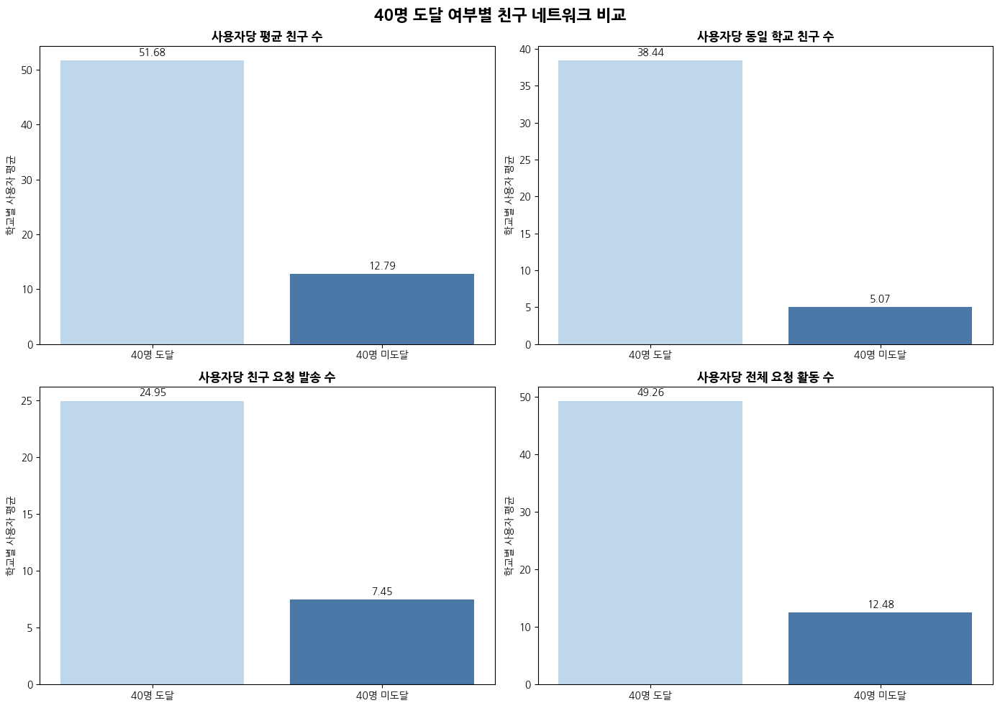

In [ ]:
# 40명 도달 여부별 현재 친구·요청 지표
required_growth_objects = ['school_activation', 'school_diffusion']
missing_growth_objects = [name for name in required_growth_objects if name not in globals()]
if missing_growth_objects:
    raise RuntimeError(
        '3-1 Growth 셀을 먼저 실행하세요: ' + ', '.join(missing_growth_objects)
    )

friend_columns = [
    'current_friend_count_snapshot',
    'same_school_friend_count',
    'same_school_friend_rate',
    'sent_request_count',
    'received_request_count',
    'total_request_activity_count',
    'accepted_request_record_count',
    'has_accepted_request_partner',
]
missing_friend_columns = [column for column in friend_columns if column not in users.columns]
if missing_friend_columns:
    raise ValueError('3-0 사용자 데이터에 친구 지표가 없습니다: ' + str(missing_friend_columns))

network_friend_users = users[['school_id', *friend_columns]].dropna(
    subset=['school_id']
).copy()
network_friend_users['school_id'] = pd.to_numeric(
    network_friend_users['school_id'], errors='coerce'
)
network_friend_users = network_friend_users.dropna(subset=['school_id']).copy()
network_friend_users['school_id'] = network_friend_users['school_id'].astype('int64')
for column in friend_columns:
    network_friend_users[column] = pd.to_numeric(
        network_friend_users[column], errors='coerce'
    )

school_friend_summary = (
    network_friend_users.groupby('school_id')
    .agg(
        학교평균친구수=('current_friend_count_snapshot', 'mean'),
        동일학교친구수_평균=('same_school_friend_count', 'mean'),
        동일학교친구비율_평균=('same_school_friend_rate', 'mean'),
        발송요청수_평균=('sent_request_count', 'mean'),
        수신요청수_평균=('received_request_count', 'mean'),
        전체요청활동수_평균=('total_request_activity_count', 'mean'),
        수락요청수_평균=('accepted_request_record_count', 'mean'),
        요청수락경험률_평균=('has_accepted_request_partner', 'mean'),
    )
    .reset_index()
)
school_friend_summary['동일학교친구비율_평균'] *= 100
school_friend_summary['요청수락경험률_평균'] *= 100

reach_friend = school_activation[
    ['school_id', '40명_도달여부']
].merge(school_friend_summary, on='school_id', how='left')
reach_friend_summary = (
    reach_friend.groupby('40명_도달여부')
    .agg(
        학교수=('school_id', 'nunique'),
        학교평균친구수_평균=('학교평균친구수', 'mean'),
        학교평균친구수_중앙값=('학교평균친구수', 'median'),
        동일학교친구수_평균=('동일학교친구수_평균', 'mean'),
        동일학교친구비율_평균=('동일학교친구비율_평균', 'mean'),
        발송요청수_평균=('발송요청수_평균', 'mean'),
        수신요청수_평균=('수신요청수_평균', 'mean'),
        전체요청활동수_평균=('전체요청활동수_평균', 'mean'),
        수락요청수_평균=('수락요청수_평균', 'mean'),
        요청수락경험률_평균=('요청수락경험률_평균', 'mean'),
    )
    .reset_index()
)
reach_friend_numeric = reach_friend_summary.select_dtypes(include='number').columns
reach_friend_summary[reach_friend_numeric] = (
    reach_friend_summary[reach_friend_numeric].round(2)
)
display(reach_friend_summary)

reach_plot_columns = [
    ('학교평균친구수_평균', '사용자당 평균 친구 수'),
    ('동일학교친구수_평균', '사용자당 동일 학교 친구 수'),
    ('발송요청수_평균', '사용자당 친구 요청 발송 수'),
    ('전체요청활동수_평균', '사용자당 전체 요청 활동 수'),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (column, title) in zip(axes.flatten(), reach_plot_columns):
    bars = ax.bar(
        reach_friend_summary['40명_도달여부'],
        reach_friend_summary[column],
        color=['#BFD7EA', '#4C78A8'],
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('학교별 사용자 평균')
    ax.bar_label(bars, fmt='%.2f', padding=3)
plt.suptitle('40명 도달 여부별 친구 네트워크 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.close('all')


- 학교별 평균 친구 수를 다시 평균하면 40명 도달 학교는 51.68명, 미도달 학교는 12.79명이다.
- 같은 학교 친구 비율도 74.46%와 45.46%로 차이가 크다.


,확산유형,학교수,사용자당_평균친구수,사용자당_동일학교친구수,동일학교친구비율,사용자당_발송요청수,사용자당_수신요청수,사용자당_전체요청활동수,사용자당_수락요청수,요청수락경험률,도달소요일_중앙값,최종가입자수_중앙값
0,지속 확산형,1382,55.76,42.94,76.48,25.98,26.60,52.58,40.07,97.10,8.0,235.0
1,단기 폭발형,540,59.01,45.29,76.57,28.22,28.45,56.67,43.39,97.39,9.0,185.0
2,후발 확산형,586,48.10,33.93,70.94,23.07,22.15,45.22,32.75,95.75,8.0,124.0
3,저확산형,1288,46.86,33.74,73.27,23.54,21.63,45.17,32.11,95.32,11.0,91.0


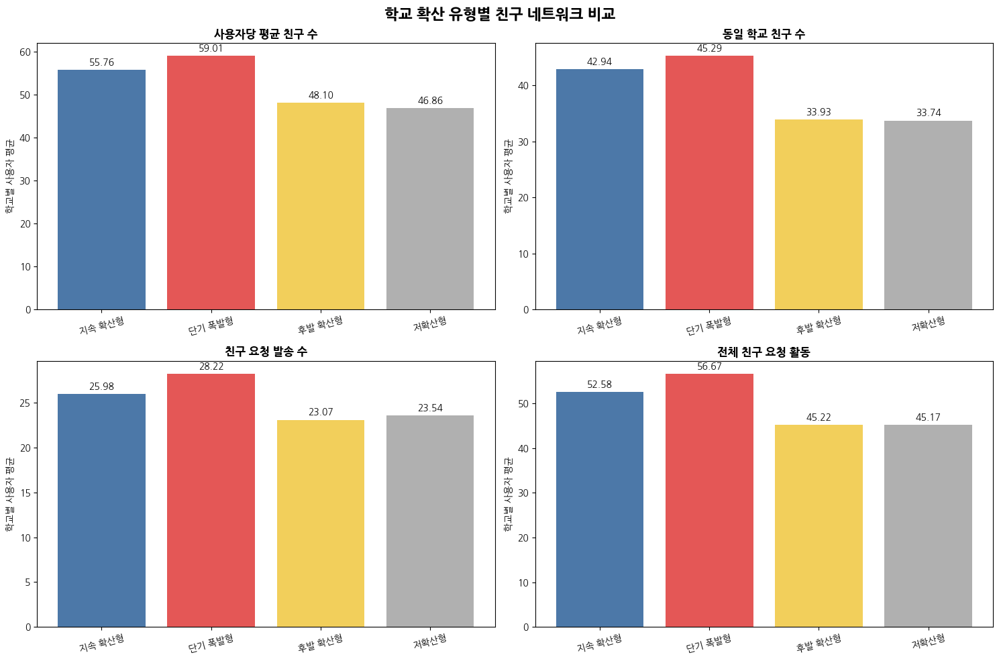

In [ ]:
# 확산 유형별 현재 관계 지표 비교
diffusion_friend = school_diffusion[
    [
        'school_id', '확산유형', '도달이전_D14_D8', '도달직전_D7_D1',
        '첫째주_D1_D7', '둘째주_D8_D14', '40명_도달소요일', '최종가입자수',
    ]
].merge(
    school_friend_summary,
    on='school_id',
    how='left',
    validate='one_to_one',
)
diffusion_friend_summary = (
    diffusion_friend.groupby('확산유형')
    .agg(
        학교수=('school_id', 'nunique'),
        사용자당_평균친구수=('학교평균친구수', 'mean'),
        사용자당_동일학교친구수=('동일학교친구수_평균', 'mean'),
        동일학교친구비율=('동일학교친구비율_평균', 'mean'),
        사용자당_발송요청수=('발송요청수_평균', 'mean'),
        사용자당_수신요청수=('수신요청수_평균', 'mean'),
        사용자당_전체요청활동수=('전체요청활동수_평균', 'mean'),
        사용자당_수락요청수=('수락요청수_평균', 'mean'),
        요청수락경험률=('요청수락경험률_평균', 'mean'),
        도달소요일_중앙값=('40명_도달소요일', 'median'),
        최종가입자수_중앙값=('최종가입자수', 'median'),
    )
    .reset_index()
)
network_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
diffusion_friend_summary['확산유형'] = pd.Categorical(
    diffusion_friend_summary['확산유형'],
    categories=network_type_order,
    ordered=True,
)
diffusion_friend_summary = diffusion_friend_summary.sort_values(
    '확산유형'
).reset_index(drop=True)
diffusion_friend_numeric = diffusion_friend_summary.select_dtypes(
    include='number'
).columns
diffusion_friend_summary[diffusion_friend_numeric] = (
    diffusion_friend_summary[diffusion_friend_numeric].round(2)
)
display(diffusion_friend_summary)

diffusion_plot_columns = [
    ('사용자당_평균친구수', '사용자당 평균 친구 수'),
    ('사용자당_동일학교친구수', '동일 학교 친구 수'),
    ('사용자당_발송요청수', '친구 요청 발송 수'),
    ('사용자당_전체요청활동수', '전체 친구 요청 활동'),
]
diffusion_colors = ['#4C78A8', '#E45756', '#F2CF5B', '#B0B0B0']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, (column, title) in zip(axes.flatten(), diffusion_plot_columns):
    bars = ax.bar(
        diffusion_friend_summary['확산유형'].astype(str),
        diffusion_friend_summary[column],
        color=diffusion_colors,
    )
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('학교별 사용자 평균')
    ax.tick_params(axis='x', rotation=15)
    ax.bar_label(bars, fmt='%.2f', padding=3)
plt.suptitle('학교 확산 유형별 친구 네트워크 비교', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

plt.close('all')


- 단기 폭발형의 학교별 평균 친구 수 평균은 59.01명으로 지속 확산형의 55.76명보다 높다.
- 현재 친구 수가 더 많은 유형이 둘째 주 가입도 더 많았던 것은 아니다. 친구 수는 현재 상태이므로 성장 당시 관계 규모로 해석하지 않는다.


In [ ]:
# Growth 확산 유형과 학교 일별 마트 연결
school_viral_clean = pd.read_csv(NETWORK_FILES["school_daily"], low_memory=False, na_values=[r"\N"], usecols=[
    "school_id", "activity_date", "current_roster_40th_signup_at",
    "sent_request_created_count", "sent_created_final_accepted_count",
    "sent_request_user_count", "new_nonstaff_account_count_current_roster"
])
school_viral_clean["school_id"] = pd.to_numeric(school_viral_clean["school_id"], errors="coerce")
school_viral_clean["activity_date"] = pd.to_datetime(school_viral_clean["activity_date"], errors="coerce").dt.normalize()
school_viral_clean["current_roster_40th_signup_at"] = pd.to_datetime(
    school_viral_clean["current_roster_40th_signup_at"], errors="coerce").dt.normalize()
school_viral_clean = school_viral_clean.dropna(subset=["school_id", "activity_date"]).copy()
if school_viral_clean.duplicated(["school_id", "activity_date"]).any():
    raise ValueError("Clean 학교 마트에 학교·날짜 중복이 있습니다. 집계 전 확인하세요.")
canonical_school_map = school_diffusion[["school_id", "확산유형"]].merge(
    school_activation[["school_id", "40명_도달일"]], on="school_id", validate="one_to_one"
).rename(columns={"40명_도달일": "D0"})
school_viral_type_clean = school_viral_clean.merge(
    canonical_school_map, on="school_id", how="inner", validate="many_to_one")
d0_check = school_viral_type_clean[["school_id", "D0", "current_roster_40th_signup_at"]].drop_duplicates()
d0_mismatch = d0_check[d0_check["current_roster_40th_signup_at"].notna()
                       & d0_check["D0"].ne(d0_check["current_roster_40th_signup_at"])]
print("D0가 Clean 마트와 다른 학교 수:", d0_mismatch["school_id"].nunique())
if not d0_mismatch.empty:
    display(d0_mismatch.head(20))
print("D0: Growth에서 계산한 학교별 40명 도달일")
school_viral_type_clean["relative_day"] = (
    school_viral_type_clean["activity_date"] - school_viral_type_clean["D0"]).dt.days
school_viral_type_clean = school_viral_type_clean[
    school_viral_type_clean["relative_day"].between(-14, 14)].copy()
for col in ["sent_request_created_count", "sent_created_final_accepted_count",
            "sent_request_user_count", "new_nonstaff_account_count_current_roster"]:
    school_viral_type_clean[col] = pd.to_numeric(school_viral_type_clean[col], errors="raise")
print("Clean 마트 결합 학교 수:", school_viral_type_clean["school_id"].nunique())

# D0를 제외한 네 구간 설정

def classify_clean_period(relative_day):
    if -14 <= relative_day <= -8:
        return "도달 이전 D-14~-8"
    elif -7 <= relative_day <= -1:
        return "도달 직전 D-7~-1"
    elif 1 <= relative_day <= 7:
        return "도달 직후 D+1~+7"
    elif 8 <= relative_day <= 14:
        return "도달 후기 D+8~+14"
    return np.nan


clean_period_order = [
    "도달 이전 D-14~-8",
    "도달 직전 D-7~-1",
    "도달 직후 D+1~+7",
    "도달 후기 D+8~+14"
]

request_period_clean = school_viral_type_clean[
    school_viral_type_clean["relative_day"].ne(0)
].copy()

request_period_clean["기간"] = (
    request_period_clean["relative_day"]
    .apply(classify_clean_period)
)

request_period_clean = request_period_clean[
    request_period_clean["기간"].notna()
].copy()

request_period_clean["기간"] = pd.Categorical(
    request_period_clean["기간"],
    categories=clean_period_order,
    ordered=True
)

print(
    "최종 분석 학교 수:",
    f"{request_period_clean['school_id'].nunique():,}개"
)

display(
    request_period_clean[
        [
            "school_id",
            "확산유형",
            "relative_day",
            "기간",
            "sent_request_created_count",
            "sent_created_final_accepted_count"
        ]
    ].head()
)

request_observed_days = request_period_clean.groupby(
    ["school_id", "확산유형", "기간"], observed=True
)["activity_date"].nunique().reset_index(name="관측날짜수")
print("학교·기간당 관측날짜 수 분포(완전한 구간은 7일):")
display(request_observed_days["관측날짜수"].value_counts().sort_index())


D0가 Clean 마트와 다른 학교 수: 0
이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.
Clean 마트 결합 학교 수: 3795
최종 분석 학교 수: 3,795개


,school_id,확산유형,relative_day,기간,sent_request_created_count,sent_created_final_accepted_count
30,4,단기 폭발형,-14,도달 이전 D-14~-8,0,0
31,4,단기 폭발형,-13,도달 이전 D-14~-8,0,0
32,4,단기 폭발형,-12,도달 이전 D-14~-8,0,0
33,4,단기 폭발형,-11,도달 이전 D-14~-8,0,0
34,4,단기 폭발형,-10,도달 이전 D-14~-8,0,0


학교·기간당 관측날짜 수 분포(완전한 구간은 7일):


,count
관측날짜수,
7,15180


- Growth 확산 유형과 학교 일별 마트가 연결된 학교는 3,795개다. 네 구간 모두 학교당 7일씩 관측됐다.


집계 학교 수: 3,795개
집계 데이터 수: 15,180행


,school_id,확산유형,기간,신규가입자수,친구요청발송수,친구요청발송사용자일수,최종수락요청수,친구요청수락률(%),신규가입자당_친구요청수
0,4,단기 폭발형,도달 이전 D-14~-8,0,0,0,0,NaN,NaN
1,4,단기 폭발형,도달 직전 D-7~-1,15,22,12,22,100.000000,1.466667
2,4,단기 폭발형,도달 직후 D+1~+7,169,3725,401,3156,84.724832,22.041420
3,4,단기 폭발형,도달 후기 D+8~+14,4,146,54,99,67.808219,36.500000
4,5,저확산형,도달 이전 D-14~-8,0,0,0,0,NaN,NaN
5,5,저확산형,도달 직전 D-7~-1,19,86,17,67,77.906977,4.526316
6,5,저확산형,도달 직후 D+1~+7,65,2390,274,1755,73.430962,36.769231
7,5,저확산형,도달 후기 D+8~+14,2,257,50,139,54.085603,128.500000
8,6,지속 확산형,도달 이전 D-14~-8,2,8,2,6,75.000000,4.000000
9,6,지속 확산형,도달 직전 D-7~-1,21,60,18,60,100.000000,2.857143


,확산유형,기간,학교수,학교당_평균신규가입자,학교당_평균친구요청,학교당_중앙값친구요청,평균_발송사용자일수,전체신규가입자수,전체친구요청수,전체수락요청수,친구요청수락률(%),신규가입자당_친구요청수
0,지속 확산형,도달 이전 D-14~-8,1382,1.45,3.73,0.0,1.00,2010,5157,4275,82.90,2.57
1,지속 확산형,도달 직전 D-7~-1,1382,18.13,85.69,60.0,15.53,25061,118427,100683,85.02,4.73
2,지속 확산형,도달 직후 D+1~+7,1382,146.25,4298.96,3937.0,410.43,202113,5941163,4738092,79.75,29.40
3,지속 확산형,도달 후기 D+8~+14,1382,24.00,934.51,723.0,136.77,33162,1291494,922635,71.44,38.94
4,단기 폭발형,도달 이전 D-14~-8,540,1.85,4.35,0.0,1.20,1001,2351,2009,85.45,2.35
5,단기 폭발형,도달 직전 D-7~-1,540,16.92,87.77,56.0,14.35,9136,47397,39638,83.63,5.19
6,단기 폭발형,도달 직후 D+1~+7,540,120.51,4303.58,3983.0,371.84,65077,2323931,1829080,78.71,35.71
7,단기 폭발형,도달 후기 D+8~+14,540,4.29,272.74,247.5,52.20,2317,147280,89671,60.88,63.56
8,후발 확산형,도달 이전 D-14~-8,586,2.33,10.97,0.0,1.99,1365,6429,5066,78.80,4.71
9,후발 확산형,도달 직전 D-7~-1,586,22.36,151.39,125.5,22.69,13102,88717,72058,81.22,6.77


,확산유형,기간,학교수,학교당_평균신규가입자,학교당_평균친구요청,친구요청수락률(%),신규가입자당_친구요청수
0,지속 확산형,도달 이전 D-14~-8,1382,1.45,3.73,82.90,2.57
1,지속 확산형,도달 직전 D-7~-1,1382,18.13,85.69,85.02,4.73
2,지속 확산형,도달 직후 D+1~+7,1382,146.25,4298.96,79.75,29.40
3,지속 확산형,도달 후기 D+8~+14,1382,24.00,934.51,71.44,38.94
4,단기 폭발형,도달 이전 D-14~-8,540,1.85,4.35,85.45,2.35
5,단기 폭발형,도달 직전 D-7~-1,540,16.92,87.77,83.63,5.19
6,단기 폭발형,도달 직후 D+1~+7,540,120.51,4303.58,78.71,35.71
7,단기 폭발형,도달 후기 D+8~+14,540,4.29,272.74,60.88,63.56
8,후발 확산형,도달 이전 D-14~-8,586,2.33,10.97,78.80,4.71
9,후발 확산형,도달 직전 D-7~-1,586,22.36,151.39,81.22,6.77


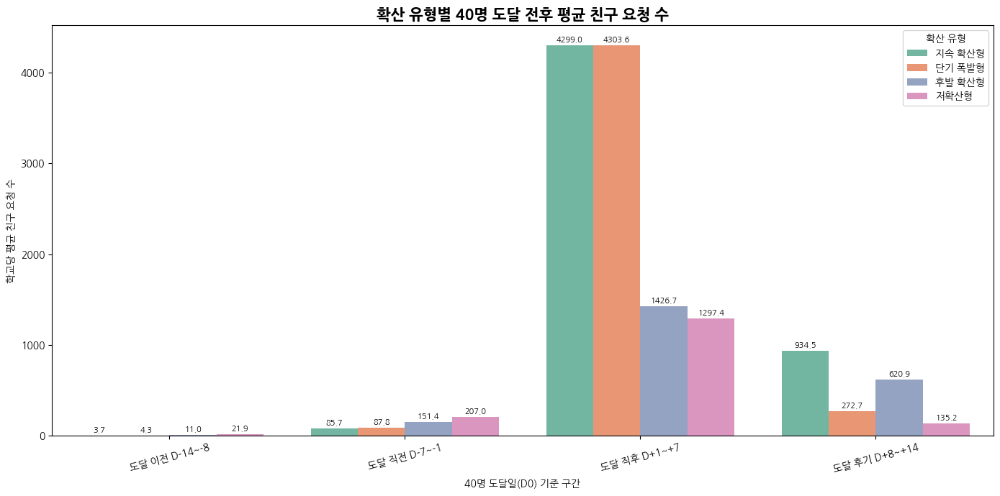

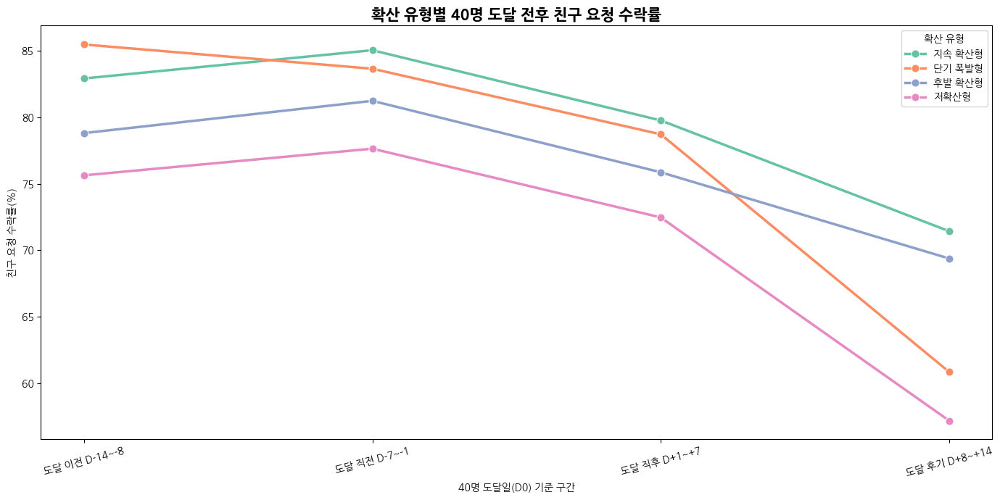

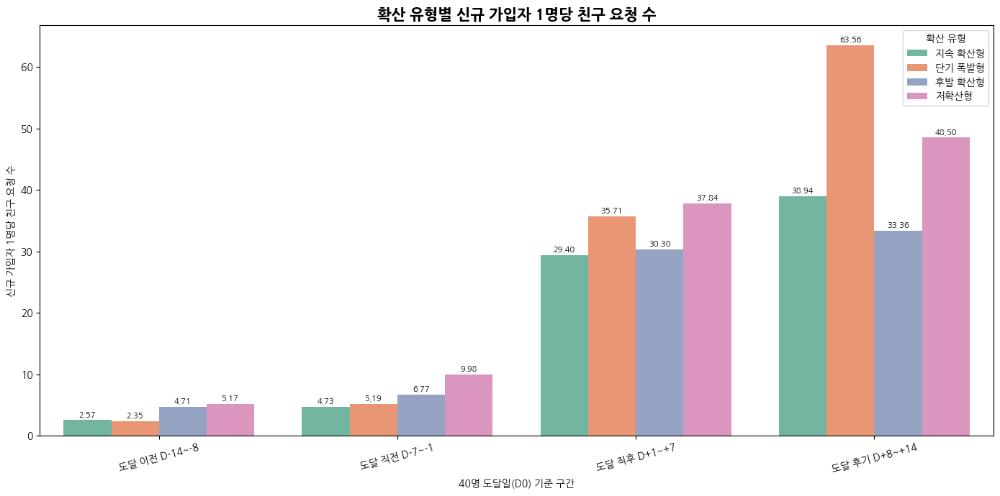

[3-2 완료] 사용이 끝난 변수 231개 정리
[3-2 완료] Python 사용 RAM 3.94 GB / 시스템 여유 RAM 8.27 GB


In [ ]:
# 학교·구간별 친구 요청 지표 계산

school_request_period_clean = (
    request_period_clean
    .groupby(
        ["school_id", "확산유형", "기간"],
        observed=True
    )
    .agg(
        신규가입자수=(
            "new_nonstaff_account_count_current_roster",
            "sum"
        ),
        친구요청발송수=(
            "sent_request_created_count",
            "sum"
        ),
        친구요청발송사용자일수=(
            "sent_request_user_count",
            "sum"
        ),
        최종수락요청수=(
            "sent_created_final_accepted_count",
            "sum"
        )
    )
    .reset_index()
)

# 친구 요청 수락률
school_request_period_clean["친구요청수락률(%)"] = np.where(
    school_request_period_clean["친구요청발송수"] > 0,
    (
        school_request_period_clean["최종수락요청수"]
        / school_request_period_clean["친구요청발송수"]
        * 100
    ),
    np.nan
)

# 신규 가입자 1명당 친구 요청 수
school_request_period_clean[
    "신규가입자당_친구요청수"
] = np.where(
    school_request_period_clean["신규가입자수"] > 0,
    (
        school_request_period_clean["친구요청발송수"]
        / school_request_period_clean["신규가입자수"]
    ),
    np.nan
)

print(
    "집계 학교 수:",
    f"{school_request_period_clean['school_id'].nunique():,}개"
)

print(
    "집계 데이터 수:",
    f"{len(school_request_period_clean):,}행"
)

display(school_request_period_clean.head(12))

# 확산 유형·구간별 친구 요청 비교

type_request_summary_clean = (
    school_request_period_clean
    .groupby(
        ["확산유형", "기간"],
        observed=True
    )
    .agg(
        학교수=(
            "school_id",
            "nunique"
        ),
        학교당_평균신규가입자=(
            "신규가입자수",
            "mean"
        ),
        학교당_평균친구요청=(
            "친구요청발송수",
            "mean"
        ),
        학교당_중앙값친구요청=(
            "친구요청발송수",
            "median"
        ),
        평균_발송사용자일수=(
            "친구요청발송사용자일수",
            "mean"
        ),
        전체신규가입자수=(
            "신규가입자수",
            "sum"
        ),
        전체친구요청수=(
            "친구요청발송수",
            "sum"
        ),
        전체수락요청수=(
            "최종수락요청수",
            "sum"
        )
    )
    .reset_index()
)

# 전체 요청을 기준으로 한 가중 수락률
type_request_summary_clean["친구요청수락률(%)"] = np.where(
    type_request_summary_clean["전체친구요청수"] > 0,
    (
        type_request_summary_clean["전체수락요청수"]
        / type_request_summary_clean["전체친구요청수"]
        * 100
    ),
    np.nan
)

# 신규 가입자 1명당 친구 요청 수
type_request_summary_clean[
    "신규가입자당_친구요청수"
] = np.where(
    type_request_summary_clean["전체신규가입자수"] > 0,
    (
        type_request_summary_clean["전체친구요청수"]
        / type_request_summary_clean["전체신규가입자수"]
    ),
    np.nan
)

# 확산 유형 출력 순서
type_order = [
    "지속 확산형",
    "단기 폭발형",
    "후발 확산형",
    "저확산형"
]

type_request_summary_clean["확산유형"] = pd.Categorical(
    type_request_summary_clean["확산유형"],
    categories=type_order,
    ordered=True
)

type_request_summary_clean = (
    type_request_summary_clean
    .sort_values(["확산유형", "기간"])
    .reset_index(drop=True)
)

# 소수점 정리
round_columns = [
    "학교당_평균신규가입자",
    "학교당_평균친구요청",
    "학교당_중앙값친구요청",
    "평균_발송사용자일수",
    "친구요청수락률(%)",
    "신규가입자당_친구요청수"
]

type_request_summary_clean[round_columns] = (
    type_request_summary_clean[round_columns]
    .round(2)
)

display(type_request_summary_clean)

# 핵심 지표만 출력

request_core_result = type_request_summary_clean[
    [
        "확산유형",
        "기간",
        "학교수",
        "학교당_평균신규가입자",
        "학교당_평균친구요청",
        "친구요청수락률(%)",
        "신규가입자당_친구요청수"
    ]
].copy()

display(request_core_result)

# 확산 유형별 평균 친구 요청 수

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=type_request_summary_clean,
    x="기간",
    y="학교당_평균친구요청",
    hue="확산유형",
    hue_order=type_order,
    palette="Set2"
)

plt.title(
    "확산 유형별 40명 도달 전후 평균 친구 요청 수",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("학교당 평균 친구 요청 수")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

# 확산 유형별 친구 요청 수락률

plt.figure(figsize=(14, 7))

ax = sns.lineplot(
    data=type_request_summary_clean,
    x="기간",
    y="친구요청수락률(%)",
    hue="확산유형",
    hue_order=type_order,
    marker="o",
    linewidth=2.5,
    markersize=8,
    palette="Set2"
)

plt.title(
    "확산 유형별 40명 도달 전후 친구 요청 수락률",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("친구 요청 수락률(%)")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

plt.tight_layout()
plt.show()

# 확산 유형별 신규 가입자당 친구 요청 수

plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=type_request_summary_clean,
    x="기간",
    y="신규가입자당_친구요청수",
    hue="확산유형",
    hue_order=type_order,
    palette="Set2"
)

plt.title(
    "확산 유형별 신규 가입자 1명당 친구 요청 수",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("40명 도달일(D0) 기준 구간")
plt.ylabel("신규 가입자 1명당 친구 요청 수")
plt.xticks(rotation=15)
plt.legend(title="확산 유형")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=2,
        fontsize=8
    )

plt.tight_layout()
plt.show()

team7_release_unused('187', '3-2 완료')
team7_close_connections('network')
plt.close('all')


- 지속 확산형과 단기 폭발형의 첫째 주 학교당 요청은 4,298.96건과 4,303.58건으로 비슷했지만, 둘째 주는 934.51건과 272.74건으로 달랐다.
- 결합된 3,795개 학교에서 두 마트의 40명 도달일은 일치했다.
- 신규 가입자당 요청 수의 분자에는 기존 사용자의 요청도 포함되므로 신규 가입자 개인의 평균 발송량은 아니다.


## 3-3. Content

- 질문 공급의 다양성·반복과 투표 기록·다음 질문 이용의 관계를 살펴본다.


### 3-3-1. 분석 범위와 질문 데이터 연결

- 질문 자료가 있는 10개 학교를 대상으로 문구·후보·투표·가입 정보를 연결했다.
- 분석 기준은 생성된 질문조각이다. 생성시각과 실제 화면 노출시각은 다르며, 투표 기록률의 분모도 실제 노출 수가 아니다.


In [ ]:
# Content 분석 환경 · 정제 마트 연결
team7_content_assets = globals().get('team7_content_assets', {})
team7_release_unused('187', 'Content 시작 전')
team7_close_connections('source', 'network')
pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 160)
pd.set_option('display.width', 260)
team7_chart_style('whitegrid')
ROOT = Path('/content')
ANALYSIS_DIR = ROOT / 'team7_analysis' / 'content'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
CACHE_DIR = OUTPUT_DIR / 'cache'
content_processed_root = Path(globals().get('PREPROCESSED_ROOT', '/content/team7_processed'))
content_question_dir = Path(globals().get('QUESTION_OUTPUT_DIR', content_processed_root / 'question_candidate'))
content_network_dir = Path(globals().get('NETWORK_OUTPUT_DIR', content_processed_root / 'viral_school'))
PATHS = {'qset': content_question_dir / 'mart_question_set_record_v2_clean.csv.gz', 'piece': content_question_dir / 'mart_question_piece_record_v2_clean.csv.gz', 'vote': content_question_dir / 'mart_vote_record_v2_clean.csv.gz', 'candidate': content_question_dir / 'mart_question_candidate_exposure_v2_clean.csv.gz', 'text': MART_DIR / 'mart_question_exposure.csv.gz', 'profile': content_network_dir / 'mart_user_acquisition_profile_v2_clean.csv.gz'}
missing_content_inputs = [str(path) for path in PATHS.values() if not path.exists()]
if missing_content_inputs:
    raise FileNotFoundError('Content 분석에 필요한 2-1·2-2 전처리 파일이 없습니다. 전처리를 먼저 실행하세요:\n- ' + '\n- '.join(missing_content_inputs))

def content_sql_path(path):
    return Path(path).as_posix().replace("'", "''")
try:
    content_con.close()
except (NameError, AttributeError):
    pass
content_con = team7_connect('content')
content_con.execute('PRAGMA threads=2')
for name, path in PATHS.items():
    content_con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_csv_auto('{content_sql_path(path)}', header=true)")
con = content_con
MODEL_NAME = 'jhgan/ko-sroberta-multitask'
RANDOM_STATE = 42
print('Content 정제 마트 연결 완료:', len(PATHS), '개')
print('텍스트 임베딩 모델:', MODEL_NAME)


[Content 시작 전] 사용이 끝난 변수 0개 정리
[Content 시작 전] Python 사용 RAM 3.37 GB / 시스템 여유 RAM 8.78 GB
Content 정제 마트 연결 완료: 6 개
텍스트 임베딩 모델: jhgan/ko-sroberta-multitask


- 질문 상태는 추출 시점의 값이다. 과거 스킵 흔적과 현재 투표 기록이 함께 남을 수 있으므로 두 비율을 더해 전체 행동을 계산할 수 없다.


In [ ]:
# 분석 모집단 · 문구·사용자 연결 점검
scope = con.execute("\nWITH s AS (\n  SELECT 'question_set' mart, COUNT(*) rows_all,\n         SUM(CASE WHEN analysis_eligible_question_set_flag=1 THEN 1 ELSE 0 END) rows_eligible,\n         MIN(question_set_created_at) min_at, MAX(question_set_created_at) max_at,\n         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_question_set_flag=1) schools\n  FROM qset\n  UNION ALL\n  SELECT 'question_piece', COUNT(*), SUM(CASE WHEN analysis_eligible_piece_relation_flag=1 THEN 1 ELSE 0 END),\n         MIN(question_piece_created_at), MAX(question_piece_created_at),\n         COUNT(DISTINCT resolved_owner_current_school_id) FILTER (WHERE analysis_eligible_piece_relation_flag=1)\n  FROM piece\n  UNION ALL\n  SELECT 'vote_record', COUNT(*), SUM(CASE WHEN analysis_eligible_vote_record_flag=1 THEN 1 ELSE 0 END),\n         MIN(vote_record_created_at), MAX(vote_record_created_at),\n         COUNT(DISTINCT voter_current_school_id) FILTER (WHERE analysis_eligible_vote_record_flag=1)\n  FROM vote\n  UNION ALL\n  SELECT 'candidate_raw', COUNT(*), SUM(CASE WHEN analysis_eligible_candidate_raw_flag=1 THEN 1 ELSE 0 END),\n         MIN(candidate_source_created_at), MAX(candidate_source_created_at),\n         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_candidate_raw_flag=1)\n  FROM candidate\n  UNION ALL\n  SELECT 'candidate_canonical', COUNT(*), SUM(CASE WHEN analysis_eligible_candidate_canonical_flag=1 THEN 1 ELSE 0 END),\n         MIN(candidate_source_created_at), MAX(candidate_source_created_at),\n         COUNT(DISTINCT owner_current_school_id) FILTER (WHERE analysis_eligible_candidate_canonical_flag=1)\n  FROM candidate\n)\nSELECT * FROM s\n").df()
display(scope)
text_qa = con.execute("\nWITH td AS (\n  SELECT CAST(question_piece_id AS VARCHAR) question_piece_id,\n         COUNT(DISTINCT NULLIF(TRIM(question_text), '')) text_n,\n         MAX(NULLIF(TRIM(question_text), '')) question_text\n  FROM text GROUP BY 1\n), p AS (\n  SELECT CAST(question_piece_id AS VARCHAR) question_piece_id\n  FROM piece WHERE analysis_eligible_piece_relation_flag=1\n)\nSELECT COUNT(*) eligible_piece_rows,\n       SUM(CASE WHEN td.question_text IS NOT NULL THEN 1 ELSE 0 END) text_matched_rows,\n       SUM(CASE WHEN td.text_n > 1 THEN 1 ELSE 0 END) multi_text_piece_rows,\n       SUM(CASE WHEN td.question_text IS NULL THEN 1 ELSE 0 END) text_missing_rows\nFROM p LEFT JOIN td USING(question_piece_id)\n").df()
profile_qa = con.execute('\nWITH p AS (\n  SELECT DISTINCT CAST(resolved_owner_user_id AS VARCHAR) user_id\n  FROM piece WHERE analysis_eligible_piece_relation_flag=1\n), u AS (\n  SELECT CAST(user_id AS VARCHAR) user_id, MIN(signup_at) signup_at, COUNT(*) n\n  FROM profile WHERE analysis_eligible_nonstaff_flag=1 GROUP BY 1\n)\nSELECT COUNT(*) owners, SUM(CASE WHEN u.signup_at IS NOT NULL THEN 1 ELSE 0 END) signup_matched,\n       SUM(CASE WHEN u.n>1 THEN 1 ELSE 0 END) duplicated_profile_ids\nFROM p LEFT JOIN u USING(user_id)\n').df()
display(Markdown('**질문 문구 연결 QA**'))
display(text_qa)
display(Markdown('**가입일 연결 QA**'))
display(profile_qa)
assert int(text_qa.loc[0, 'multi_text_piece_rows']) == 0
assert int(text_qa.loc[0, 'text_missing_rows']) == 0
assert int(profile_qa.loc[0, 'duplicated_profile_ids']) == 0


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,mart,rows_all,rows_eligible,min_at,max_at,schools
0,question_set,158384,158384.0,2023-04-28 12:27:23,2024-05-07 11:32:30,10
1,question_piece,1265476,1265476.0,2023-04-28 12:27:22,2024-05-07 11:32:30,10
2,vote_record,1217558,1217558.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10
3,candidate_raw,4769609,4769609.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10
4,candidate_canonical,4769609,4769034.0,2023-04-28 12:27:49,2024-05-08 01:36:18,10


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**질문 문구 연결 QA**

,eligible_piece_rows,text_matched_rows,multi_text_piece_rows,text_missing_rows
0,1265476,1265476.0,0.0,0.0


**가입일 연결 QA**

,owners,signup_matched,duplicated_profile_ids
0,4972,4972.0,0.0


- 질문조각 1,265,476건의 문구와 사용자 4,972명의 가입 정보가 모두 연결됐다.
- 후보 분석에는 중복 등을 정리한 정규 후보 자료를 사용했다. 원본 후보 행 수와는 집계 기준이 다르다.


In [ ]:
# 질문조각 단위 분석 테이블 구성
con.execute("\nCREATE OR REPLACE TEMP TABLE text_dim AS\nSELECT CAST(question_piece_id AS VARCHAR) question_piece_id,\n       MAX(NULLIF(TRIM(question_text), '')) question_text\nFROM text GROUP BY 1;\n\nCREATE OR REPLACE TEMP TABLE signup_dim AS\nSELECT CAST(user_id AS VARCHAR) user_id, MIN(TRY_CAST(signup_at AS TIMESTAMP)) signup_at\nFROM profile WHERE analysis_eligible_nonstaff_flag=1 GROUP BY 1;\n\nCREATE OR REPLACE TEMP TABLE candidate_piece AS\nSELECT CAST(question_piece_id AS VARCHAR) question_piece_id,\n       1 candidate_source_observed,\n       COUNT(*) candidate_count,\n       COUNT(DISTINCT CAST(candidate_user_id AS VARCHAR)) candidate_distinct_count,\n       MAX(CAST(duplicate_candidate_pair_flag AS INTEGER)) has_duplicate_candidate,\n       MAX(CAST(self_candidate_flag AS INTEGER)) has_self_candidate,\n       MAX(CAST(current_friend_any_direction_flag AS INTEGER)) has_current_friend_candidate,\n       MAX(CAST(current_friend_mutual_flag AS INTEGER)) has_mutual_friend_candidate,\n       MAX(CAST(same_school_current_flag AS INTEGER)) has_same_school_candidate,\n       MAX(CAST(same_school_grade_current_flag AS INTEGER)) has_same_grade_candidate,\n       MAX(CAST(same_school_grade_class_current_flag AS INTEGER)) has_same_class_candidate,\n       AVG(CAST(current_friend_any_direction_flag AS DOUBLE)) current_friend_share,\n       AVG(CAST(same_school_current_flag AS DOUBLE)) same_school_share,\n       AVG(CAST(same_school_grade_current_flag AS DOUBLE)) same_grade_share,\n       AVG(CAST(same_school_grade_class_current_flag AS DOUBLE)) same_class_share,\n       MAX(CASE WHEN selected_candidate_canonical_pair_flag=1 AND current_friend_any_direction_flag=1 THEN 1 ELSE 0 END) chose_current_friend,\n       MAX(CASE WHEN selected_candidate_canonical_pair_flag=1 AND same_school_grade_class_current_flag=1 THEN 1 ELSE 0 END) chose_same_class,\n       MAX(CASE WHEN current_friend_any_direction_flag=1 OR same_school_current_flag=1 OR self_candidate_flag=1 THEN 1 ELSE 0 END) has_any_currently_known_candidate\nFROM candidate\nWHERE analysis_eligible_candidate_canonical_flag=1\nGROUP BY 1;\n\nCREATE OR REPLACE TEMP TABLE piece_core_sql AS\nSELECT CAST(p.question_piece_id AS VARCHAR) question_piece_id,\n       CAST(p.question_id AS VARCHAR) question_id,\n       TRY_CAST(p.question_piece_created_at AS TIMESTAMP) piece_created_at,\n       CAST(p.single_question_set_id AS VARCHAR) question_set_id,\n       CAST(p.resolved_owner_user_id AS VARCHAR) owner_user_id,\n       CAST(p.resolved_owner_current_school_id AS VARCHAR) school_id,\n       TRY_CAST(p.single_question_position AS INTEGER) question_position,\n       CAST(p.vote_record_exists_flag AS INTEGER) vote_record_exists,\n       CAST(p.raw_is_voted AS INTEGER) raw_is_voted,\n       CAST(p.raw_is_skipped AS INTEGER) raw_is_skipped,\n       p.piece_snapshot_state,\n       td.question_text,\n       s.signup_at,\n       DATE_DIFF('day', s.signup_at, TRY_CAST(p.question_piece_created_at AS TIMESTAMP)) signup_elapsed_days,\n       COALESCE(c.candidate_source_observed, 0) candidate_source_observed,\n       c.candidate_count,\n       c.candidate_distinct_count,\n       c.has_duplicate_candidate,\n       c.has_self_candidate,\n       c.has_current_friend_candidate,\n       c.has_mutual_friend_candidate,\n       c.has_same_school_candidate,\n       c.has_same_grade_candidate,\n       c.has_same_class_candidate,\n       c.current_friend_share,\n       c.same_school_share,\n       c.same_grade_share,\n       c.same_class_share,\n       c.chose_current_friend,\n       c.chose_same_class,\n       CASE WHEN c.candidate_source_observed IS NULL THEN NULL\n            ELSE 1-c.has_any_currently_known_candidate END unknown_only_current_proxy\nFROM piece p\nJOIN text_dim td ON CAST(p.question_piece_id AS VARCHAR)=td.question_piece_id\nLEFT JOIN candidate_piece c ON CAST(p.question_piece_id AS VARCHAR)=c.question_piece_id\nLEFT JOIN signup_dim s ON CAST(p.resolved_owner_user_id AS VARCHAR)=s.user_id\nWHERE p.analysis_eligible_piece_relation_flag=1;\n")
piece = con.execute('SELECT * FROM piece_core_sql ORDER BY piece_created_at, question_piece_id').df()
piece['piece_created_at'] = pd.to_datetime(piece['piece_created_at'])
piece['signup_at'] = pd.to_datetime(piece['signup_at'])
piece['month'] = piece['piece_created_at'].dt.to_period('M').astype(str)
piece['is_2023_may'] = piece['month'].eq('2023-05').astype(int)
piece['candidate_count_band'] = pd.cut(piece['candidate_count'], [0, 1, 2, 3, 5, 10, np.inf], labels=['1', '2', '3', '4-5', '6-10', '11+'], include_lowest=True)
print(f'분석용 질문조각: {len(piece):,}행 / 사용자 {piece.owner_user_id.nunique():,}명 / 학교 {piece.school_id.nunique()}개')
print(f'기간: {piece.piece_created_at.min()} ~ {piece.piece_created_at.max()}')
display(piece.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

분석용 질문조각: 1,265,476행 / 사용자 4,972명 / 학교 10개
기간: 2023-04-28 12:27:22 ~ 2024-05-07 11:32:30


,question_piece_id,question_id,piece_created_at,question_set_id,owner_user_id,school_id,question_position,vote_record_exists,raw_is_voted,raw_is_skipped,piece_snapshot_state,question_text,signup_at,signup_elapsed_days,candidate_source_observed,candidate_count,candidate_distinct_count,has_duplicate_candidate,has_self_candidate,has_current_friend_candidate,has_mutual_friend_candidate,has_same_school_candidate,has_same_grade_candidate,has_same_class_candidate,current_friend_share,same_school_share,same_grade_share,same_class_share,chose_current_friend,chose_same_class,unknown_only_current_proxy,month,is_2023_may,candidate_count_band
0,998458,252,2023-04-28 12:27:22,99817,849436,271,1,1,1,0,VOTED_HISTORY_ONLY,손이 가장 이쁘게 생겼을거 같은 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.50,1,0,0,2023-04,0,4-5
1,998459,244,2023-04-28 12:27:22,99817,849436,271,2,1,1,0,VOTED_HISTORY_ONLY,대학교에서 학생회장할 것 같은 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,1,0,2023-04,0,4-5
2,998460,183,2023-04-28 12:27:22,99817,849436,271,3,1,1,0,VOTED_HISTORY_ONLY,나의 자존감을 가장 많이 높여줬던 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,0,0,2023-04,0,4-5
3,998461,101,2023-04-28 12:27:22,99817,849436,271,4,1,1,0,VOTED_HISTORY_ONLY,미래의 틱톡커는?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,1,0,2023-04,0,4-5
4,998462,209,2023-04-28 12:27:22,99817,849436,271,5,1,1,0,VOTED_HISTORY_ONLY,항상 좋은 냄새가 나는 사람은?,2023-04-28 02:54:59.981972,0,1,4,4,0,0,1,1,1,1,1,1.0,1.0,1.0,0.75,1,0,0,2023-04,0,4-5


- 질문조각 한 건을 기준으로 문구·투표·후보 정보를 모았다. 후보 원본이 없는 행은 결측으로 남겨 실제 후보 0명과 섞이지 않게 했다.


### 3-3-2. 질문 공급 규모와 의미 중복

- 질문 ID, 정규화한 문구, 의미가 비슷한 문구를 각각 세었다. 임베딩 군집은 질문의 주제를 대략 묶기 위한 탐색용 분류다.


In [ ]:
# 문구 정규화 · 질문별 공급 빈도
def normalize_text(x):
    if pd.isna(x):
        return ''
    x = unicodedata.normalize('NFKC', str(x)).lower().strip()
    x = re.sub('\\s+', ' ', x)
    x = re.sub('[^0-9a-z가-힣 ]+', '', x)
    return x.strip()
piece['question_text_normalized'] = piece['question_text'].map(normalize_text)
piece['text_len'] = piece['question_text_normalized'].str.len()
overview = pd.DataFrame({'지표': ['질문조각', '질문세트', '사용자', '학교', '질문 ID', '원문 문구', '정규화 문구', '투표 기록 보유', '과거 스킵 흔적'], '값': [len(piece), piece.question_set_id.nunique(), piece.owner_user_id.nunique(), piece.school_id.nunique(), piece.question_id.nunique(), piece.question_text.nunique(), piece.question_text_normalized.nunique(), int(piece.vote_record_exists.sum()), int(piece.raw_is_skipped.sum())]})
display(overview.style.format({'값': '{:,}'}))
text_freq = piece.groupby(['question_id', 'question_text', 'question_text_normalized'], dropna=False).agg(piece_count=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), schools=('school_id', 'nunique'), first_at=('piece_created_at', 'min'), last_at=('piece_created_at', 'max'), vote_rate=('vote_record_exists', 'mean')).reset_index().sort_values('piece_count', ascending=False)
display(text_freq.head(20))


,지표,값
0,질문조각,"1,265,476"
1,질문세트,"156,539"
2,사용자,"4,972"
3,학교,10
4,질문 ID,"4,944"
5,원문 문구,"3,899"
6,정규화 문구,"3,898"
7,투표 기록 보유,"1,217,558"
8,과거 스킵 흔적,"1,127"


,question_id,question_text,question_text_normalized,piece_count,users,schools,first_at,last_at,vote_rate
770,170,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?,처음 보는 사람과 가장 빨리 친해질 것 같은 사람은,2030,1444,10,2023-04-28 12:31:58,2023-08-20 07:51:17,0.983251
2090,290,모든 사람과 잘 지낼 것 같은 사람은?,모든 사람과 잘 지낼 것 같은 사람은,2021,1480,10,2023-04-28 12:31:10,2024-03-30 16:10:45,0.982682
759,169,축제에서 공연을 제일 잘 할거 같은 사람은?,축제에서 공연을 제일 잘 할거 같은 사람은,2017,1442,10,2023-04-28 12:29:34,2024-01-14 08:46:57,0.983639
1221,211,앞으로의 인생을 가장 재미있게 살것 같은 사람은?,앞으로의 인생을 가장 재미있게 살것 같은 사람은,2009,1447,10,2023-04-28 12:32:18,2024-01-20 04:28:43,0.982578
946,186,vote,vote,1991,1447,10,2023-04-28 12:30:30,2023-11-23 08:31:32,0.979910
2310,310,반려동물과 가장 잘 지낼거 같은 사람은?,반려동물과 가장 잘 지낼거 같은 사람은,1985,1441,10,2023-04-28 12:31:44,2023-08-06 14:58:42,0.985390
22,102,여기서 제일 특이한 친구는?,여기서 제일 특이한 친구는,1975,1416,10,2023-04-28 12:29:04,2023-07-20 11:53:19,0.985316
1584,244,대학교에서 학생회장할 것 같은 사람은?,대학교에서 학생회장할 것 같은 사람은,1975,1456,10,2023-04-28 12:27:22,2023-10-12 08:21:37,0.985316
2299,309,흰티에 청바지가 잘 어울릴것 같은 사람은?,흰티에 청바지가 잘 어울릴것 같은 사람은,1963,1432,10,2023-04-28 12:33:34,2023-11-07 14:50:44,0.987774
572,152,숨겨진 댄싱 머신이라고 생각하는 사람은?,숨겨진 댄싱 머신이라고 생각하는 사람은,1956,1431,10,2023-04-28 12:28:38,2023-07-12 11:36:59,0.988241


- 가장 많이 공급된 질문 ID는 ‘처음 보는 사람과 가장 빨리 친해질 것 같은 사람은?’으로, 질문조각 2,030건에 연결됐다.
- 표의 공급 상위 20개 질문은 모두 10개 학교에서 관측됐다. 공급이 많은 질문부터 학교 공통으로 쓰인 모습이다.


**질문세트 상태별 기초 구조**

,status,qsets,avg_piece_refs,avg_existing_pieces,complete_10_reference_rate,median_opening_delay_seconds
0,CURRENT_STATUS_F,153411,10.0,7.924849,0.339989,2400.0
1,CURRENT_STATUS_O,4407,10.0,9.997504,0.997731,2400.0
2,CURRENT_STATUS_C,566,10.0,9.996466,0.996466,2400.0


**학교별 공급 규모와 사용자 표준화 지표**

,school_id,users,qsets,pieces,question_ids,normalized_texts,vote_record_rate,first_at,last_at,pieces_per_user,texts_per_1000_pieces
1,1719,546,19904,166065,3585,3328,0.968103,2023-05-13 10:06:38,2024-05-07 00:15:00,304.148352,20.040346
9,5520,493,18759,158640,4374,3876,0.970424,2023-05-09 08:46:57,2024-03-19 12:57:35,321.784990,24.432678
5,4426,481,17594,137894,4139,3848,0.966351,2023-05-20 10:21:15,2024-05-03 17:23:50,286.681913,27.905493
8,5491,474,15572,124193,3267,3106,0.962977,2023-05-09 10:42:41,2024-05-07 11:32:30,262.010549,25.009461
4,369,557,15552,123613,3547,3319,0.956380,2023-05-02 21:37:17,2024-03-17 08:25:21,221.926391,26.849927
2,271,478,14710,122141,4035,3699,0.962519,2023-04-28 12:27:22,2024-04-12 10:37:55,255.525105,30.284671
6,4516,489,14706,119878,4091,3733,0.960793,2023-05-02 21:29:38,2024-05-06 10:58:20,245.149284,31.139992
7,5372,500,14420,112700,3734,3498,0.957223,2023-05-11 13:11:10,2024-04-22 15:39:12,225.400000,31.038154
0,1478,477,13701,111438,4210,3778,0.959260,2023-05-07 23:01:44,2024-04-20 04:53:17,233.622642,33.902260
3,352,477,11621,88914,3255,3086,0.947590,2023-05-05 08:07:12,2024-03-31 04:51:26,186.402516,34.707695


,top_text_share,text_count,piece_share
0,0.01,39,0.066947
1,0.05,195,0.287304
2,0.10,390,0.529817
3,0.20,780,0.740024


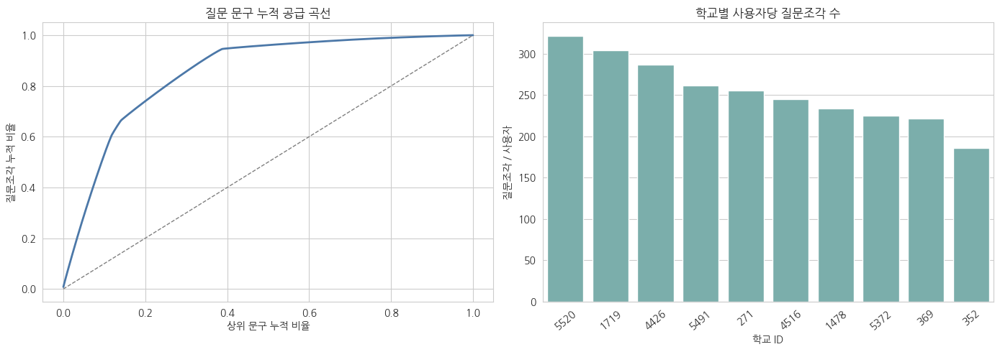

In [ ]:
# 질문세트 구조 · 학교별 공급량 · 상위 문구 집중도
qset_basic = con.execute('\nSELECT question_set_status_label status,\n       COUNT(*) qsets,\n       AVG(piece_list_length_recalc) avg_piece_refs,\n       AVG(referenced_piece_existing_count) avg_existing_pieces,\n       AVG(CAST(complete_10_piece_reference_flag AS DOUBLE)) complete_10_reference_rate,\n       MEDIAN(opening_delay_seconds_recalc) median_opening_delay_seconds\nFROM qset\nWHERE analysis_eligible_question_set_flag=1\nGROUP BY 1 ORDER BY qsets DESC\n').df()
school_basic = piece.groupby('school_id').agg(users=('owner_user_id', 'nunique'), qsets=('question_set_id', 'nunique'), pieces=('question_piece_id', 'size'), question_ids=('question_id', 'nunique'), normalized_texts=('question_text_normalized', 'nunique'), vote_record_rate=('vote_record_exists', 'mean'), first_at=('piece_created_at', 'min'), last_at=('piece_created_at', 'max')).reset_index()
school_basic['pieces_per_user'] = school_basic.pieces / school_basic.users
school_basic['texts_per_1000_pieces'] = school_basic.normalized_texts / school_basic.pieces * 1000
display(Markdown('**질문세트 상태별 기초 구조**'))
display(qset_basic)
display(Markdown('**학교별 공급 규모와 사용자 표준화 지표**'))
display(school_basic.sort_values('pieces', ascending=False))
freq = text_freq.groupby('question_text_normalized').piece_count.sum().sort_values(ascending=False)
cum = freq.cumsum() / freq.sum()
x = np.arange(1, len(freq) + 1) / len(freq)
pareto = pd.DataFrame({'rank': np.arange(1, len(freq) + 1), 'text_share': x, 'cumulative_piece_share': cum.values})
pareto_points = []
for pct in [0.01, 0.05, 0.1, 0.2]:
    n = max(1, int(np.ceil(len(freq) * pct)))
    pareto_points.append({'top_text_share': pct, 'text_count': n, 'piece_share': freq.iloc[:n].sum() / freq.sum()})
pareto_points = pd.DataFrame(pareto_points)
display(pareto_points)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(x, cum.values, color='#4C78A8', lw=2)
ax[0].plot([0, 1], [0, 1], '--', color='gray', lw=1)
ax[0].set(title='질문 문구 누적 공급 곡선', xlabel='상위 문구 누적 비율', ylabel='질문조각 누적 비율')
sns.barplot(data=school_basic.sort_values('pieces_per_user', ascending=False), x='school_id', y='pieces_per_user', color='#72B7B2', ax=ax[1])
ax[1].set(title='학교별 사용자당 질문조각 수', xlabel='학교 ID', ylabel='질문조각 / 사용자')
ax[1].tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()
plt.close('all')


- 공급 상위 10% 문구가 전체 질문조각의 53.0%, 상위 20%가 74.0%를 차지했다. 소수 문구에 공급이 몰려 있다.
- 세트가 참조하는 ID는 10개여도 연결된 질문조각 수는 달랐다. 학교별 공급량과 사용자 수도 달라 이후 비교에 함께 반영했다.


,month,pieces,qsets,users,question_ids,normalized_texts,vote_rate,skip_history_rate,texts_active,new_texts,new_text_share
0,2023-04,33651,4116,350,227,227,0.995661,0.000119,227,227,1.000000
1,2023-05,1144964,141717,4907,1536,1513,0.975259,0.000669,1513,1286,0.849967
2,2023-06,74466,9285,1797,4429,3894,0.818320,0.003599,3894,2384,0.612224
3,2023-07,6040,691,359,3497,2943,0.583609,0.006788,2943,1,0.000340
4,2023-08,2273,262,152,1784,1626,0.567532,0.002200,1626,0,0.000000
5,2023-09,2054,226,159,1530,1510,0.368062,0.008763,1510,0,0.000000
6,2023-10,452,48,41,416,412,0.207965,0.013274,412,0,0.000000
7,2023-11,306,36,20,289,285,0.581699,0.000000,285,0,0.000000
8,2023-12,555,69,25,512,508,0.657658,0.000000,508,0,0.000000
9,2024-01,309,44,19,296,293,0.469256,0.048544,293,0,0.000000


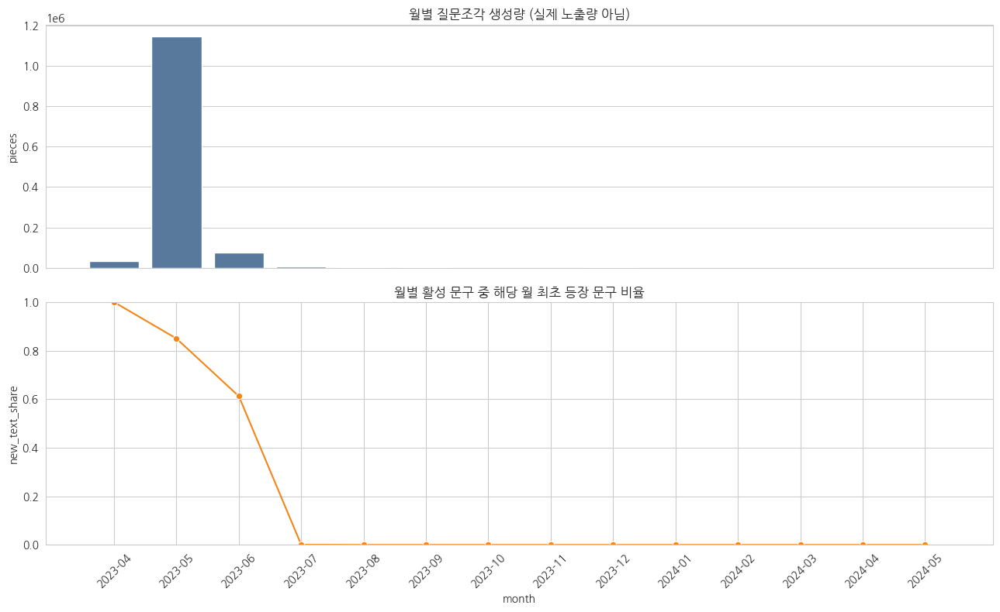

In [ ]:
# 월별 질문 공급 · 신규 문구 비중
monthly = piece.groupby('month').agg(pieces=('question_piece_id', 'size'), qsets=('question_set_id', 'nunique'), users=('owner_user_id', 'nunique'), question_ids=('question_id', 'nunique'), normalized_texts=('question_text_normalized', 'nunique'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean')).reset_index()
first_text_month = piece.groupby('question_text_normalized')['month'].min()
piece['text_first_month'] = piece['question_text_normalized'].map(first_text_month)
new_monthly = piece[['month', 'question_text_normalized', 'text_first_month']].drop_duplicates().assign(is_new=lambda d: d.month.eq(d.text_first_month)).groupby('month').agg(texts_active=('question_text_normalized', 'size'), new_texts=('is_new', 'sum')).reset_index()
new_monthly['new_text_share'] = new_monthly.new_texts / new_monthly.texts_active
monthly = monthly.merge(new_monthly, on='month', how='left')
display(monthly)
fig, ax = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
sns.barplot(data=monthly, x='month', y='pieces', color='#4C78A8', ax=ax[0])
ax[0].set_title('월별 질문조각 생성량 (실제 노출량 아님)')
ax[0].set_xlabel('')
ax[0].tick_params(axis='x', rotation=45)
sns.lineplot(data=monthly, x='month', y='new_text_share', marker='o', color='#F58518', ax=ax[1])
ax[1].set_title('월별 활성 문구 중 해당 월 최초 등장 문구 비율')
ax[1].set_ylim(0, 1)
ax[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
plt.close('all')


- 새 문구는 2023년 5~6월에 집중됐다. 7월에는 1개만 추가됐고, 이후에는 새 문구가 관측되지 않았다.
- 같은 시기에 질문조각과 이용자 수도 크게 줄었다. 신규 문구 부족과 이용 감소가 함께 나타났지만 선후 원인은 알기 어렵다.


In [ ]:
# 월별 공급 집중도 · 문구 다양성
def hhi_from_counts(s):
    p = s / s.sum()
    return float((p ** 2).sum())

def normalized_entropy(s):
    p = (s / s.sum()).values
    if len(p) <= 1:
        return 0.0
    return float(stats.entropy(p) / np.log(len(p)))
concentration = []
for month, g in piece.groupby('month'):
    cnt = g.question_text_normalized.value_counts()
    concentration.append({'month': month, 'hhi': hhi_from_counts(cnt), 'normalized_entropy': normalized_entropy(cnt), 'top10_share': cnt.head(10).sum() / cnt.sum(), 'texts': len(cnt)})
concentration = pd.DataFrame(concentration)
display(concentration)


,month,hhi,normalized_entropy,top10_share,texts
0,2023-04,0.004454,0.998979,0.054174,227
1,2023-05,0.001067,0.964632,0.023044,1513
2,2023-06,0.000493,0.968787,0.019861,3894
3,2023-07,0.000521,0.978576,0.019205,2943
4,2023-08,0.000812,0.985049,0.025517,1626
5,2023-09,0.000847,0.986705,0.026777,1510
6,2023-10,0.002633,0.994504,0.048673,412
7,2023-11,0.003845,0.994300,0.075163,285
8,2023-12,0.002139,0.994603,0.045045,508
9,2024-01,0.003592,0.996425,0.067961,293


- 상위 10개 문구 비중은 2023년 6월 1.99%에서 2024년 4월 24.0%로 높아졌다. 이때 공급된 문구 수는 3,894개에서 48개로 줄었다.
- 후기의 집중도 상승에는 전체 공급 규모가 작아진 영향도 있다.


In [ ]:
# 형태소 빈도 · 동일 문구의 복수 ID
unique_text = piece.groupby('question_text_normalized').agg(question_text=('question_text', 'first'), piece_count=('question_piece_id', 'size'), question_id_count=('question_id', 'nunique'), users=('owner_user_id', 'nunique'), first_at=('piece_created_at', 'min'), last_at=('piece_created_at', 'max')).reset_index()
kiwi = Kiwi(num_workers=1)
KEEP_TAG_PREFIX = ('N', 'V', 'MA', 'XR', 'SL')

def kiwi_tokens(text):
    toks = []
    for token in kiwi.tokenize(text):
        if token.tag.startswith(KEEP_TAG_PREFIX) and len(token.form) >= 1:
            toks.append(token.form)
    return toks
unique_text['tokens'] = unique_text.question_text_normalized.map(kiwi_tokens)
unique_text['token_text'] = unique_text.tokens.map(lambda x: ' '.join(x))
all_terms = Counter()
for toks, w in zip(unique_text.tokens, unique_text.piece_count):
    all_terms.update({t: int(w) * c for t, c in Counter(toks).items()})
term_df = pd.DataFrame(all_terms.most_common(100), columns=['term', 'weighted_count'])
display(term_df.head(30))
exact = piece.groupby('question_text_normalized').agg(rows=('question_piece_id', 'size'), question_ids=('question_id', 'nunique'), example=('question_text', 'first')).reset_index()
exact['multi_id_same_text'] = exact.question_ids.gt(1)
exact_summary = pd.DataFrame({'metric': ['정규화 고유 문구', '둘 이상 질문 ID가 같은 문구', '그 문구가 차지한 질문조각 비율'], 'value': [len(exact), int(exact.multi_id_same_text.sum()), exact.loc[exact.multi_id_same_text, 'rows'].sum() / exact.rows.sum()]})
display(exact_summary)
display(exact.sort_values(['question_ids', 'rows'], ascending=False).head(20))
team7_release_unused('199', '형태소 분석 완료')


,term,weighted_count
0,사람,1009056
1,같,605907
2,것,543685
3,가장,345160
4,친구,230775
5,잘,188461
6,싶,174124
7,하,169349
8,제일,136041
9,있,113263


,metric,value
0,정규화 고유 문구,3898.000000
1,둘 이상 질문 ID가 같은 문구,988.000000
2,그 문구가 차지한 질문조각 비율,0.055566


,question_text_normalized,rows,question_ids,example,multi_id_same_text
84,vote,10169,55,vote,True
23,2세가 가장 귀여울 것 같은 사람은,2228,3,2세가 가장 귀여울 것 같은 사람은?,True
1098,눈이 제일 큰 사람은,788,3,눈이 제일 큰 사람은?,True
428,같이 밥먹고 싶은 사람은,385,3,같이 밥먹고 싶은 사람은?,True
3181,지금 뭐하는지 궁금한 친구,55,3,지금 뭐하는지 궁금한 친구,True
2826,인생 2회차인 것 같은 사람은,51,3,인생 2회차인 것 같은 사람은?,True
496,같이 캠핑가고 싶은 사람은,2169,2,같이 캠핑가고 싶은 사람은?,True
1252,라면 잘 끓일 것 같은 사람은,2157,2,라면 잘 끓일 것 같은 사람은?,True
125,가장 깔끔할 것 같은 친구는,1998,2,가장 깔끔할 것 같은 친구는?,True
286,가장 잘생긴 사람은,1959,2,가장 잘생긴 사람은?,True


[형태소 분석 완료] 사용이 끝난 변수 22개 정리
[형태소 분석 완료] Python 사용 RAM 4.85 GB / 시스템 여유 RAM 7.33 GB


- 고유 문구 3,898개 중 988개가 둘 이상의 질문 ID에 연결됐다. 이 문구들의 공급 비중은 5.56%로, ID 수보다 실제 콘텐츠 종류가 적다.
- ‘사람’, ‘같’, ‘친구’가 여러 질문에 반복돼 단어 빈도만으로는 주제 차이가 잘 드러나지 않았다.


In [ ]:
# 한국어 문장 임베딩 · 모델 메모리 해제
team7_release_unused('199', '문장 모델 실행 전')
team7_content_assets = globals().get('team7_content_assets', {})
emb_path = CACHE_DIR / 'ko_sroberta_question_embeddings.npz'
embeddings = None
if 'texts' in team7_content_assets and 'embeddings' in team7_content_assets:
    if team7_content_assets['texts'].tolist() == unique_text.question_text_normalized.tolist():
        embeddings = team7_content_assets['embeddings']
        print('변수에 보관된 임베딩 사용:', embeddings.shape)
if embeddings is None and emb_path.exists():
    with np.load(emb_path, allow_pickle=True) as cached_embedding_file:
        if cached_embedding_file['texts'].tolist() == unique_text.question_text_normalized.tolist():
            embeddings = cached_embedding_file['embeddings'].copy()
            print('기존 런타임 임베딩 사용:', embeddings.shape)

def team7_encode_questions(texts):
    encoder = None
    try:
        encoder = SentenceTransformer(MODEL_NAME)
        encoder.eval()
        with torch.inference_mode():
            return encoder.encode(texts, batch_size=64, show_progress_bar=True, normalize_embeddings=True, convert_to_numpy=True)
    finally:
        del encoder
        team7_collect()
if embeddings is None:
    embeddings = team7_encode_questions(unique_text.question_text.tolist())
print('임베딩:', embeddings.shape)
team7_memory_report('문장 모델 해제 후')
team7_content_assets['texts'] = np.asarray(unique_text.question_text_normalized.tolist(), dtype=object)
team7_content_assets['embeddings'] = np.asarray(embeddings, dtype='float32')


[문장 모델 실행 전] 사용이 끝난 변수 0개 정리
[문장 모델 실행 전] Python 사용 RAM 4.85 GB / 시스템 여유 RAM 7.33 GB


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/495k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

임베딩: (3898, 768)
[문장 모델 해제 후] Python 사용 RAM 4.91 GB / 시스템 여유 RAM 7.28 GB


- 고유 문구를 임베딩한 뒤 질문조각에 연결해 문구 간 의미 유사도를 비교했다.


In [ ]:
# 문장 유사도 기준별 중복 후보
sim = embeddings @ embeddings.T
np.fill_diagonal(sim, -1)
nearest_idx = sim.argmax(axis=1)
nearest_sim = sim[np.arange(len(sim)), nearest_idx]
unique_text['nearest_text'] = unique_text.question_text.iloc[nearest_idx].values
unique_text['nearest_cosine'] = nearest_sim

def semantic_components(similarity, threshold):
    n = len(similarity)
    parent = np.arange(n)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = (find(a), find(b))
        if ra != rb:
            parent[rb] = ra
    ii, jj = np.where(np.triu(similarity, 1) >= threshold)
    for a, b in zip(ii, jj):
        union(int(a), int(b))
    roots = [find(i) for i in range(n)]
    relabel = {r: k for k, r in enumerate(sorted(set(roots)))}
    return (np.array([relabel[r] for r in roots]), len(ii))
semantic_rows = []
for th in [0.85, 0.9, 0.95]:
    groups, pair_n = semantic_components(sim, th)
    sizes = pd.Series(groups).value_counts()
    multi = set(sizes[sizes > 1].index)
    in_multi = np.array([g in multi for g in groups])
    weighted_share = unique_text.loc[in_multi, 'piece_count'].sum() / unique_text.piece_count.sum()
    semantic_rows.append({'threshold': th, 'similar_pairs': pair_n, 'multi_text_components': len(multi), 'unique_texts_in_component': int(in_multi.sum()), 'piece_weighted_share': weighted_share})
    if th == 0.9:
        unique_text['semantic_group_090'] = groups
semantic_sensitivity = pd.DataFrame(semantic_rows)
display(semantic_sensitivity)
pairs = []
ii, jj = np.where(np.triu(sim, 1) >= 0.9)
for a, b in zip(ii, jj):
    pairs.append((float(sim[a, b]), unique_text.question_text.iloc[a], unique_text.question_text.iloc[b], int(unique_text.piece_count.iloc[a]), int(unique_text.piece_count.iloc[b])))
pair_df = pd.DataFrame(pairs, columns=['cosine', 'question_a', 'question_b', 'count_a', 'count_b']).sort_values('cosine', ascending=False)
display(pair_df.head(30))


,threshold,similar_pairs,multi_text_components,unique_texts_in_component,piece_weighted_share
0,0.85,882,349,1040,0.329026
1,0.90,315,220,505,0.178417
2,0.95,82,77,158,0.063251


,cosine,question_a,question_b,count_a,count_b
149,1.000000,누나 /언니가 있을 것 같은 사람,누나/언니가 있을 것 같은 사람,39,27
294,0.999119,체육대회 때 이인삼각 뛴다면 누구랑 뛰고 싶어?,체육대회때 이인삼각 뛴다면 누구랑 뛰고 싶어?,38,378
193,0.998964,생일파티 때 꼭 부르고 싶은 사람은?,생일파티때 꼭 부르고 싶은 사람은?,45,31
254,0.998046,윙크 제일 잘 할 것 같은 사람은?,윙크 제일 잘할 것 같은 사람은?,359,50
64,0.997795,같이 동물원 가고 싶은 사람은?,같이 동물원 가고싶은 사람은?,386,19
280,0.997337,졸업식 때 가장 많이 울 것 같은 사람,졸업식때 가장 많이 울 것 같은 사람,402,35
313,0.996848,화나면 가장 무서울 것 같은 사람은?,화나면 가장 무서울 것 같을 사람은?,1835,366
189,0.996587,사진 잘 찍어줄 것 같은 사람은?,사진을 잘 찍어줄 것 같은 사람은?,38,383
83,0.995075,같이 코인노래방 가고 싶은 사람은?,같이 코인노래방을 가고 싶은 사람은?,343,1569
60,0.993036,같이 꽃구경 가고 싶은 사람?,같이 꽃구경 가고 싶은 사람은?,33,322


- 유사도 0.90 이상인 문구 쌍은 315개다. 이 의미군에 속한 문구가 전체 공급의 17.84%를 차지했다.
- 띄어쓰기 차이뿐 아니라 표현이 조금 다른 질문도 묶였다. 이 기준의 중복에는 의미가 비슷한 문구까지 포함된다.


In [ ]:
# 문장 임베딩 군집 수 비교 · 대표 질문
pca = PCA(n_components=min(50, embeddings.shape[1]), random_state=RANDOM_STATE)
emb50 = pca.fit_transform(embeddings)
k_scores = []
models = {}
for k in [6, 8, 10, 12, 14, 16]:
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, batch_size=512, n_init=20)
    labels = km.fit_predict(emb50)
    score = silhouette_score(emb50, labels, sample_size=min(3000, len(labels)), random_state=RANDOM_STATE)
    k_scores.append({'k': k, 'silhouette': score})
    models[k] = (km, labels)
k_scores = pd.DataFrame(k_scores)
best_k = int(k_scores.loc[k_scores.silhouette.idxmax(), 'k'])
theme_model, theme_labels = models[best_k]
unique_text['theme_id'] = theme_labels
display(k_scores)
print('선택된 테마 수:', best_k)
vectorizer = TfidfVectorizer(token_pattern='(?u)\\b\\w+\\b', min_df=2, max_df=0.95)
X = vectorizer.fit_transform(unique_text.token_text)
terms = np.array(vectorizer.get_feature_names_out())
theme_rows = []
for t in sorted(unique_text.theme_id.unique()):
    idx = np.where(theme_labels == t)[0]
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).ravel()
    top_terms = terms[mean_tfidf.argsort()[-10:][::-1]].tolist()
    center = theme_model.cluster_centers_[t]
    d = np.linalg.norm(emb50[idx] - center, axis=1)
    reps = unique_text.question_text.iloc[idx[np.argsort(d)[:3]]].tolist()
    theme_rows.append({'theme_id': int(t), 'unique_texts': len(idx), 'piece_count': int(unique_text.piece_count.iloc[idx].sum()), 'top_terms': ' / '.join(top_terms), 'representative_questions': ' | '.join(reps)})
theme_summary = pd.DataFrame(theme_rows).sort_values('piece_count', ascending=False)
display(theme_summary)


,k,silhouette
0,6,0.049407
1,8,0.039918
2,10,0.048165
3,12,0.049225
4,14,0.048296
5,16,0.045777


선택된 테마 수: 6


,theme_id,unique_texts,piece_count,top_terms,representative_questions
2,2,864,383076,가장 / 사람 / 잘 / 같 / 것 / 제일 / 어울리 / 하 / 이 / 좋,제일 금사빠일 것 같은 사람은? | 가장 기가 쎌 것 같은 사람은? | 깜지를 가장...
1,1,838,318391,사람 / 싶 / 같 / 것 / 같이 / 하 / 주 / 보 / 나 / 있,나랑 설레는 키차이일 것 같은 사람은? | 산리오 좋아할 것 같은 사람은? | 기...
4,4,831,199138,친구 / 같 / 것 / 싶 / 가장 / 하 / 같이 / 주 / 있 / 잘,얘랑 친구하길 잘했다 싶은 친구는? | 가장 인싸일 것 같은 친구는? | 가장 쩝쩝...
3,3,550,186627,것 / 같 / 사람 / 하 / 이 / 있 / 잘 / 가 / 되 / 수,미래에 올림픽에서 금메달을 딸 것 같은 사람은? | 로블록스 할 것 같은 사람은? ...
5,5,405,91753,것 / 같 / 사람 / 안 / 하 / 못 / 먹 / 있 / 가장 / 보,이 사람 빼고 당신에 대한 기억을 전부 지운다면? | 배터리 50% 밑으로 내려가면...
0,0,410,86491,사람 / 같 / 것 / 잘 / 친구 / 이 / 어울리 / 하 / 있 / 나,이 친구 굉장하다 | 초록색이 잘 어울리는 사람 | 노란색이 잘 어울리는 사람


- 실루엣 점수가 가장 높은 6개 테마를 선택했지만 점수는 0.049로 낮았다. 뚜렷한 주제 구분보다는 대표 문구를 함께 읽는 탐색용 분류로 해석한다.


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


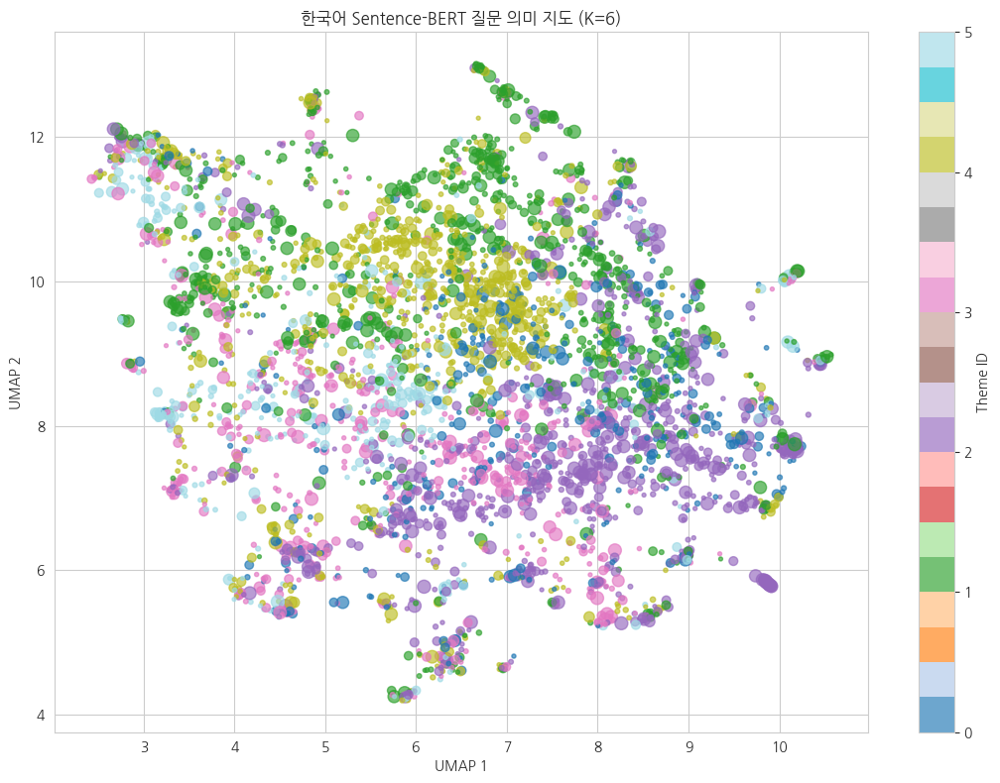

In [ ]:
# 질문 의미 지도 · 테마·의미군 연결
reducer = umap.UMAP(n_neighbors=25, min_dist=0.15, metric='cosine', random_state=RANDOM_STATE)
xy = reducer.fit_transform(embeddings)
unique_text['umap_x'] = xy[:, 0]
unique_text['umap_y'] = xy[:, 1]
fig, ax = plt.subplots(figsize=(11, 8))
sc = ax.scatter(unique_text.umap_x, unique_text.umap_y, c=unique_text.theme_id, cmap='tab20', s=np.clip(np.sqrt(unique_text.piece_count) * 2, 8, 100), alpha=0.65)
ax.set_title(f'한국어 Sentence-BERT 질문 의미 지도 (K={best_k})')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
plt.colorbar(sc, ax=ax, label='Theme ID')
plt.tight_layout()
plt.show()
text_to_theme = unique_text.set_index('question_text_normalized')['theme_id']
text_to_semgroup = unique_text.set_index('question_text_normalized')['semantic_group_090']
piece['theme_id'] = piece.question_text_normalized.map(text_to_theme)
piece['semantic_group_090'] = piece.question_text_normalized.map(text_to_semgroup)
plt.close('all')
team7_content_assets['text_features'] = unique_text[['question_text_normalized', 'token_text', 'semantic_group_090', 'umap_x', 'umap_y', 'piece_count']].copy()


- UMAP은 문구 사이의 의미상 거리를 평면에 옮긴 그림이다. 점의 크기는 공급량이며, 가로·세로축 자체에 주제나 성과의 의미는 없다.


,seed_a,seed_b,adjusted_rand_index
count,10.000000,10.000000,10.000000
mean,24.200000,72.600000,0.387146
std,21.806217,29.762766,0.081019
min,7.000000,19.000000,0.293031
25%,7.000000,49.750000,0.306413
50%,19.000000,73.000000,0.396917
75%,36.250000,101.000000,0.444974
max,73.000000,101.000000,0.511913


,first_month,new_texts,median_prior_similarity,p90_prior_similarity,mean_semantic_novelty
0,2023-04,227,0.638347,0.771956,0.367214
1,2023-05,1286,0.707951,0.856975,0.292145
2,2023-06,2384,0.750003,0.890048,0.247606
3,2023-07,1,0.872981,0.872981,0.127019


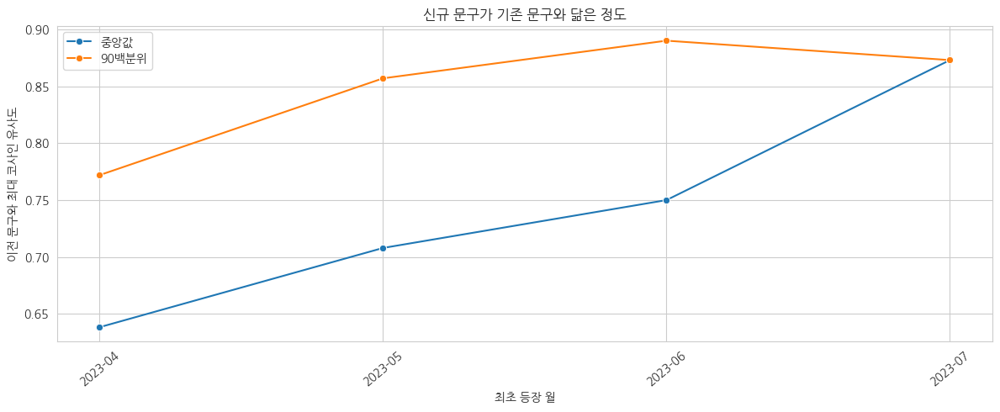

In [ ]:
# 테마 분류 안정성 · 신규 문구의 기존 질문 유사도
seed_labels = {RANDOM_STATE: theme_labels}
for seed in [7, 19, 73, 101]:
    km_seed = MiniBatchKMeans(n_clusters=best_k, random_state=seed, batch_size=512, n_init=20)
    seed_labels[seed] = km_seed.fit_predict(emb50)
stability = []
seeds = sorted(seed_labels)
for i, a in enumerate(seeds):
    for b in seeds[i + 1:]:
        stability.append({'seed_a': a, 'seed_b': b, 'adjusted_rand_index': adjusted_rand_score(seed_labels[a], seed_labels[b])})
theme_stability = pd.DataFrame(stability)
display(theme_stability.describe())
order = np.argsort(pd.to_datetime(unique_text.first_at).values)
prior_max = np.full(len(unique_text), np.nan)
seen = []
for idx in order:
    if seen:
        prior_max[idx] = float(sim[idx, seen].max())
    seen.append(int(idx))
unique_text['max_similarity_to_prior_text'] = prior_max
unique_text['semantic_novelty_to_prior'] = 1 - prior_max
unique_text['first_month'] = pd.to_datetime(unique_text.first_at).dt.to_period('M').astype(str)
novelty_month = unique_text.groupby('first_month').agg(new_texts=('question_text_normalized', 'size'), median_prior_similarity=('max_similarity_to_prior_text', 'median'), p90_prior_similarity=('max_similarity_to_prior_text', lambda s: s.quantile(0.9)), mean_semantic_novelty=('semantic_novelty_to_prior', 'mean')).reset_index()
display(novelty_month)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=novelty_month, x='first_month', y='median_prior_similarity', marker='o', label='중앙값', ax=ax)
sns.lineplot(data=novelty_month, x='first_month', y='p90_prior_similarity', marker='o', label='90백분위', ax=ax)
ax.set(title='신규 문구가 기존 문구와 닮은 정도', xlabel='최초 등장 월', ylabel='이전 문구와 최대 코사인 유사도')
ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()
plt.close('all')


- 초기값 간 평균 ARI는 0.387이다. 군집 배정은 실행 조건에 민감하므로 확정적인 주제 분류로 보지 않는다.
- 신규 문구와 기존 문구의 유사도 중앙값은 4월 0.638에서 6월 0.750으로 높아졌다.


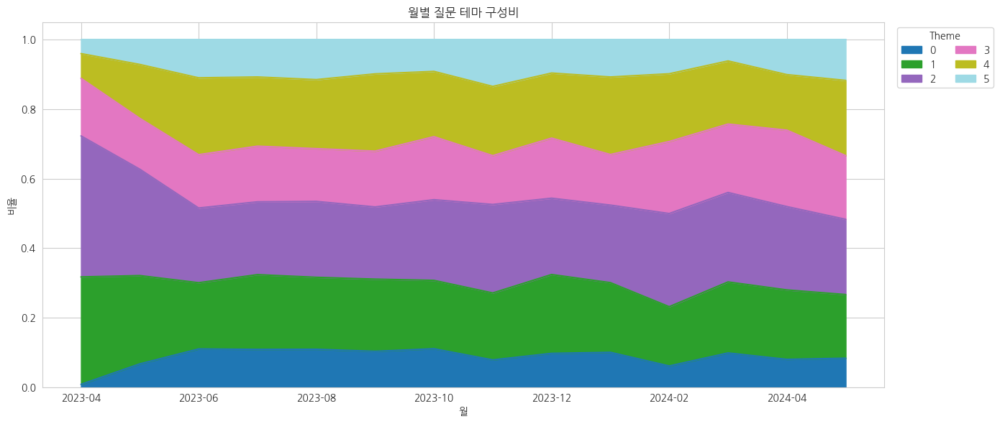

,from_month,to_month,jensen_shannon_distance
0,2023-04,2023-05,0.169315
1,2023-05,2023-06,0.118072
9,2024-01,2024-02,0.085711
10,2024-02,2024-03,0.073527
6,2023-10,2023-11,0.071633
7,2023-11,2023-12,0.066403
12,2024-04,2024-05,0.061572
11,2024-03,2024-04,0.061274
8,2023-12,2024-01,0.044236
5,2023-09,2023-10,0.039790


[질문 공급 분석 완료] 사용이 끝난 변수 32개 정리
[질문 공급 분석 완료] Python 사용 RAM 4.98 GB / 시스템 여유 RAM 7.21 GB


In [ ]:
# 월별 테마 구성 · 분포 변화
theme_month = piece.groupby(['month', 'theme_id']).size().rename('n').reset_index()
theme_month['share'] = theme_month.n / theme_month.groupby('month').n.transform('sum')
pivot = theme_month.pivot(index='month', columns='theme_id', values='share').fillna(0)
fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind='area', stacked=True, cmap='tab20', ax=ax)
ax.set_title('월별 질문 테마 구성비')
ax.set_ylabel('비율')
ax.set_xlabel('월')
ax.legend(title='Theme', bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2)
plt.tight_layout()
plt.show()
theme_shift = []
for i in range(1, len(pivot)):
    theme_shift.append({'from_month': pivot.index[i - 1], 'to_month': pivot.index[i], 'jensen_shannon_distance': float(jensenshannon(pivot.iloc[i - 1] + 1e-12, pivot.iloc[i] + 1e-12))})
theme_shift = pd.DataFrame(theme_shift)
display(theme_shift.sort_values('jensen_shannon_distance', ascending=False).head(10))
team7_release_unused('206', '질문 공급 분석 완료')
plt.close('all')


- 월간 테마 분포 차이는 2023년 4→5월 0.169로 가장 컸고, 5→6월은 0.118이었다. 2024년 4→5월은 0.062였다.
- 후기에는 공급량이 작아 분포 변화를 전체 이용 경험의 변화로 일반화하기 어렵다.


### 3-3-3. 이용 중 쌓이는 반복과 후보 구성

- 사용자별 질문 순서를 따라 문구와 후보가 다시 등장하는 횟수를 셌다.
- 친구·학교·학년·반은 현재 정보다. 질문을 받은 당시의 관계와는 차이가 있을 수 있다. 후보 기록이 있는 질문에 선택된 표본이라는 점도 후보 분석의 한계다.


,definition,repeated_rows,repeat_rate
0,동일 질문 ID,234314,0.185159
1,정규화 문구,240776,0.190265
2,의미군(>=0.90),257793,0.203712


,sequence_band,rows,users,exact_repeat_rate,semantic_repeat_rate,vote_rate,skip_history_rate
0,1-10,49717,4972,0.003419,0.004143,0.959290,0.003701
1,11-20,47569,4812,0.021211,0.023250,0.973596,0.001366
2,21-50,135457,4672,0.055125,0.059761,0.975158,0.000952
3,51-100,200394,4332,0.113511,0.121930,0.967105,0.000674
4,101-200,300331,3658,0.191738,0.205010,0.960767,0.000799
5,201-500,393137,2411,0.273345,0.291440,0.955822,0.000755
6,501+,138871,581,0.319260,0.344240,0.960179,0.000554


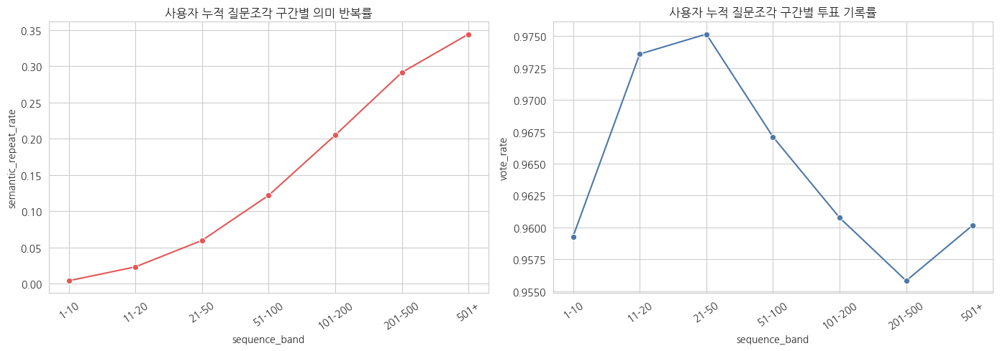

In [ ]:
# 사용자별 누적 이용 순서 · 질문 반복률
piece = piece.sort_values(['owner_user_id', 'piece_created_at', 'question_piece_id']).reset_index(drop=True)
piece['user_question_id_occurrence'] = piece.groupby(['owner_user_id', 'question_id']).cumcount() + 1
piece['user_exact_text_occurrence'] = piece.groupby(['owner_user_id', 'question_text_normalized']).cumcount() + 1
piece['user_semantic_occurrence'] = piece.groupby(['owner_user_id', 'semantic_group_090']).cumcount() + 1
piece['repeat_question_id'] = piece.user_question_id_occurrence.gt(1).astype(int)
piece['repeat_exact_text'] = piece.user_exact_text_occurrence.gt(1).astype(int)
piece['repeat_semantic_090'] = piece.user_semantic_occurrence.gt(1).astype(int)
piece['user_piece_sequence'] = piece.groupby('owner_user_id').cumcount() + 1
repeat_summary = pd.DataFrame({'definition': ['동일 질문 ID', '정규화 문구', '의미군(>=0.90)'], 'repeated_rows': [piece.repeat_question_id.sum(), piece.repeat_exact_text.sum(), piece.repeat_semantic_090.sum()], 'repeat_rate': [piece.repeat_question_id.mean(), piece.repeat_exact_text.mean(), piece.repeat_semantic_090.mean()]})
display(repeat_summary)
piece['sequence_band'] = pd.cut(piece.user_piece_sequence, [0, 10, 20, 50, 100, 200, 500, np.inf], labels=['1-10', '11-20', '21-50', '51-100', '101-200', '201-500', '501+'])
seq_summary = piece.groupby('sequence_band', observed=True).agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), exact_repeat_rate=('repeat_exact_text', 'mean'), semantic_repeat_rate=('repeat_semantic_090', 'mean'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean')).reset_index()
display(seq_summary)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=seq_summary, x='sequence_band', y='semantic_repeat_rate', marker='o', ax=ax[0], color='#E45756')
ax[0].set_title('사용자 누적 질문조각 구간별 의미 반복률')
ax[0].tick_params(axis='x', rotation=35)
sns.lineplot(data=seq_summary, x='sequence_band', y='vote_rate', marker='o', ax=ax[1], color='#4C78A8')
ax[1].set_title('사용자 누적 질문조각 구간별 투표 기록률')
ax[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()
plt.close('all')


- 반복률은 질문 ID 기준 18.52%, 문구 기준 19.03%, 의미군 기준 20.37%였다.
- 사용자별 생성 순서에서 첫 10개 질문조각의 의미 반복률은 0.41%, 501개 이상 구간은 34.42%였다. 실제 열람이 아닌 생성·배정 기록 기준이다.


In [ ]:
# 세트 내부 중복 · 가입 경과일별 반복
qset_rep = piece.dropna(subset=['question_set_id']).groupby(['owner_user_id', 'question_set_id']).agg(positions=('question_piece_id', 'size'), unique_question_ids=('question_id', 'nunique'), unique_exact_texts=('question_text_normalized', 'nunique'), unique_semantic_groups=('semantic_group_090', 'nunique'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean'), created_at=('piece_created_at', 'min')).reset_index()
qset_rep['duplicate_id_within_set'] = qset_rep.positions - qset_rep.unique_question_ids
qset_rep['duplicate_exact_within_set'] = qset_rep.positions - qset_rep.unique_exact_texts
qset_rep['duplicate_semantic_within_set'] = qset_rep.positions - qset_rep.unique_semantic_groups
qset_repeat_describe = qset_rep[['positions', 'duplicate_id_within_set', 'duplicate_exact_within_set', 'duplicate_semantic_within_set']].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
display(qset_repeat_describe)
elapsed_bins = pd.cut(piece.signup_elapsed_days, [-np.inf, -1, 0, 1, 3, 7, 14, 30, 60, 90, 180, np.inf], labels=['음수', '0일', '1일', '2-3일', '4-7일', '8-14일', '15-30일', '31-60일', '61-90일', '91-180일', '181일+'])
elapsed = piece.assign(elapsed_band=elapsed_bins).groupby('elapsed_band', observed=True).agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), unique_texts=('question_text_normalized', 'nunique'), semantic_repeat_rate=('repeat_semantic_090', 'mean'), vote_rate=('vote_record_exists', 'mean')).reset_index()
display(elapsed)


,positions,duplicate_id_within_set,duplicate_exact_within_set,duplicate_semantic_within_set
count,156539.000000,156539.0,156539.000000,156539.000000
mean,8.084094,0.0,0.002191,0.006113
std,2.228824,0.0,0.048370,0.079732
min,1.000000,0.0,0.000000,0.000000
50%,9.000000,0.0,0.000000,0.000000
90%,10.000000,0.0,0.000000,0.000000
95%,10.000000,0.0,0.000000,0.000000
99%,10.000000,0.0,0.000000,0.000000
max,10.000000,0.0,3.000000,3.000000


,elapsed_band,rows,users,unique_texts,semantic_repeat_rate,vote_rate
0,0일,144475,4292,2005,0.046022,0.984239
1,1일,189523,4046,1766,0.135857,0.995193
2,2-3일,288887,4232,1836,0.222616,0.991831
3,4-7일,315580,4064,2574,0.271982,0.978063
4,8-14일,185189,3295,3488,0.269287,0.944154
5,15-30일,107773,2367,3893,0.201405,0.864975
6,31-60일,23511,769,3692,0.101697,0.773680
7,61-90일,5415,332,2810,0.116898,0.556233
8,91-180일,3771,240,2289,0.118801,0.420313
9,181일+,1352,65,1092,0.152367,0.524408


- 한 세트 안에서 같은 질문 ID가 반복된 경우는 없었다. 문구·의미군 중복도 드물어, 반복은 여러 세트를 이용하면서 쌓이는 쪽에 가깝다.
- 가입 경과일별 결과에는 시점마다 남아 있는 이용자가 달라지는 영향도 섞여 있다.


,semantic_occurrence_band,rows,users,vote_rate,skip_history_rate,median_sequence
0,1회,1007683,4972,0.957939,0.001022,138.0
1,2회,193172,4462,0.978480,0.000399,232.0
2,3회,45480,3264,0.978892,0.000352,321.0
3,4-5회,16157,2060,0.980256,0.000186,415.0
4,6-10회,2698,669,0.969607,0.000371,581.5
5,11회+,286,84,0.944056,0.000000,966.5


,users_with_both,mean_within_user_diff,median_within_user_diff,ci95_low,ci95_high,p_value
0,4462,-0.011364,0.010839,-0.01562,-0.007107,1.745574e-07


,matched_strata,rows_in_matched_strata,adjusted_rate_diff,ci95_low,ci95_high,z
0,5976,1204053,0.010815,0.010143,0.011486,31.568141


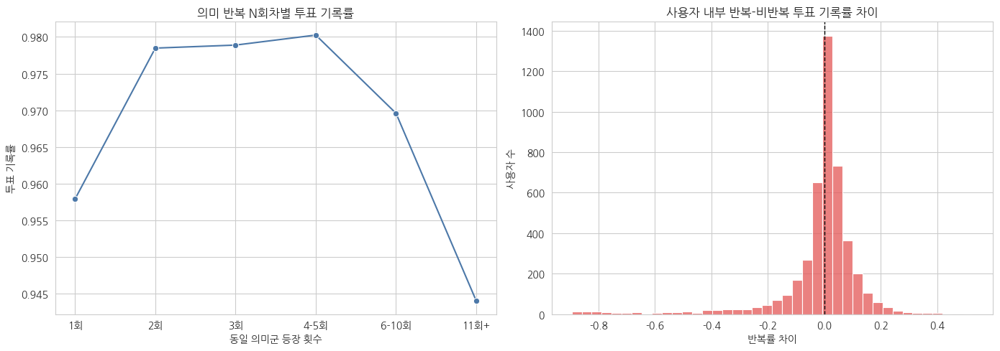

In [ ]:
# 의미 반복 횟수 · 사용자 내부·조건별 비교
piece['semantic_occurrence_band'] = pd.cut(piece.user_semantic_occurrence, [0, 1, 2, 3, 5, 10, np.inf], labels=['1회', '2회', '3회', '4-5회', '6-10회', '11회+'])
occurrence_curve = piece.groupby('semantic_occurrence_band', observed=True).agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean'), median_sequence=('user_piece_sequence', 'median')).reset_index()
display(occurrence_curve)
user_rates = piece.groupby(['owner_user_id', 'repeat_semantic_090']).vote_record_exists.mean().unstack()
paired = user_rates.dropna().rename(columns={0: 'nonrepeat_rate', 1: 'repeat_rate'})
paired['within_user_diff'] = paired.repeat_rate - paired.nonrepeat_rate
paired_test = stats.ttest_1samp(paired.within_user_diff, 0, nan_policy='omit')
within_user_result = pd.DataFrame([{'users_with_both': len(paired), 'mean_within_user_diff': paired.within_user_diff.mean(), 'median_within_user_diff': paired.within_user_diff.median(), 'ci95_low': paired.within_user_diff.mean() - 1.96 * paired.within_user_diff.std(ddof=1) / np.sqrt(len(paired)), 'ci95_high': paired.within_user_diff.mean() + 1.96 * paired.within_user_diff.std(ddof=1) / np.sqrt(len(paired)), 'p_value': paired_test.pvalue}])
display(within_user_result)
strata_cols = ['school_id', 'month', 'theme_id', 'question_position', 'sequence_band']
strata = piece.groupby(strata_cols + ['repeat_semantic_090'], observed=True).agg(n=('vote_record_exists', 'size'), k=('vote_record_exists', 'sum')).reset_index()
strata['rate'] = strata.k / strata.n
wide = strata.pivot(index=strata_cols, columns='repeat_semantic_090', values=['n', 'rate']).dropna().reset_index()
wide.columns = ['_'.join(map(str, c)).rstrip('_') if isinstance(c, tuple) else c for c in wide.columns]
wide['diff'] = wide['rate_1'] - wide['rate_0']
wide['weight'] = 2 * wide['n_0'] * wide['n_1'] / (wide['n_0'] + wide['n_1'])
adjusted_diff = np.average(wide['diff'], weights=wide['weight'])
stratum_se = np.sqrt(np.sum(wide.weight ** 2 * (wide.rate_0 * (1 - wide.rate_0) / wide.n_0 + wide.rate_1 * (1 - wide.rate_1) / wide.n_1)) / wide.weight.sum() ** 2)
stratified_result = pd.DataFrame([{'matched_strata': len(wide), 'rows_in_matched_strata': int((wide.n_0 + wide.n_1).sum()), 'adjusted_rate_diff': adjusted_diff, 'ci95_low': adjusted_diff - 1.96 * stratum_se, 'ci95_high': adjusted_diff + 1.96 * stratum_se, 'z': adjusted_diff / stratum_se}])
display(stratified_result)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=occurrence_curve, x='semantic_occurrence_band', y='vote_rate', marker='o', ax=ax[0], color='#4C78A8')
ax[0].set(title='의미 반복 N회차별 투표 기록률', xlabel='동일 의미군 등장 횟수', ylabel='투표 기록률')
sns.histplot(paired.within_user_diff, bins=40, ax=ax[1], color='#E45756')
ax[1].axvline(0, color='black', ls='--', lw=1)
ax[1].set(title='사용자 내부 반복-비반복 투표 기록률 차이', xlabel='반복률 차이', ylabel='사용자 수')
plt.tight_layout()
plt.show()
plt.close('all')


- 2~5회 반복된 질문의 투표 기록률은 첫 등장보다 높다.
- 사용자 내부 평균 차이는 -1.14%p, 조건을 나눈 비교는 +1.08%p로 방향이 달라 반복만의 영향은 단정하기 어렵다.


**후보 원천 관측 여부 × 투표 기록 여부**

vote_record_exists,0,1
candidate_source_observed,,
0,47887,0
1,31,1217558


,metric,rows,denominator,denominator_n,rate
0,후보 원천 미관측(전체 질문조각 기준),47887,전체 질문조각,1265476,0.037841
1,후보 중복 존재,133,후보 원천 관측 질문조각,1217589,0.000109
2,자기 자신 포함,4802,후보 원천 관측 질문조각,1217589,0.003944
3,현재 친구 포함,1217405,후보 원천 관측 질문조각,1217589,0.999849
4,현재 상호친구 포함,1217303,후보 원천 관측 질문조각,1217589,0.999765
5,같은 학교 포함,1206289,후보 원천 관측 질문조각,1217589,0.990719
6,같은 학년 포함,1203912,후보 원천 관측 질문조각,1217589,0.988767
7,같은 반 포함,832816,후보 원천 관측 질문조각,1217589,0.683988
8,현재 관계상 모르는 후보만,9,후보 원천 관측 질문조각,1217589,0.000007


,candidate_count_band,rows,users,selected_record_rate,skip_history_rate,friend_available_rate,self_candidate_rate,unknown_only_rate
0,1,40,30,1.000000,0.000000,1.0,0.0,0.0
1,2,3039,1112,0.999671,0.000000,0.999013,0.001645,0.0
2,3,95138,3604,0.999685,0.000000,0.999674,0.003752,0.000011
3,4-5,1119368,4845,1.000000,0.000026,0.999866,0.003967,0.000007
4,6-10,4,4,1.000000,0.000000,1.0,0.0,0.0


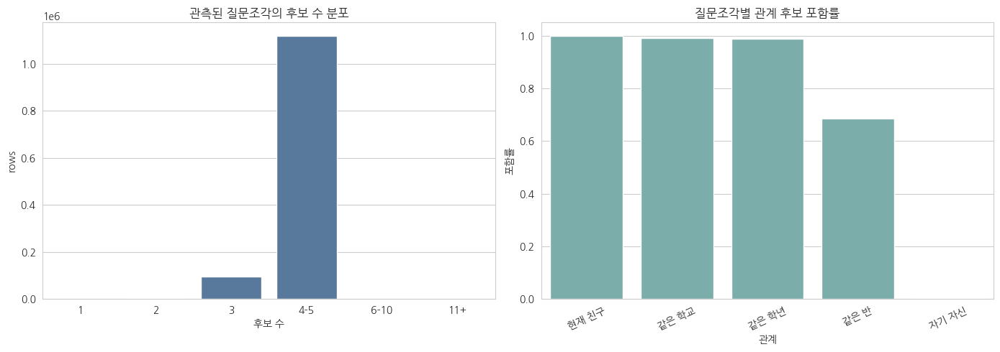

In [ ]:
# 후보 관측 범위 · 후보 수·관계 품질
observability = pd.crosstab(piece.candidate_source_observed, piece.vote_record_exists, rownames=['candidate_source_observed'], colnames=['vote_record_exists']).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
display(Markdown('**후보 원천 관측 여부 × 투표 기록 여부**'))
display(observability)
candidate_observed = piece[piece.candidate_source_observed.eq(1)].copy()
candidate_summary = pd.DataFrame({'metric': ['후보 원천 미관측(전체 질문조각 기준)', '후보 중복 존재', '자기 자신 포함', '현재 친구 포함', '현재 상호친구 포함', '같은 학교 포함', '같은 학년 포함', '같은 반 포함', '현재 관계상 모르는 후보만'], 'rows': [(piece.candidate_source_observed == 0).sum(), candidate_observed.has_duplicate_candidate.sum(), candidate_observed.has_self_candidate.sum(), candidate_observed.has_current_friend_candidate.sum(), candidate_observed.has_mutual_friend_candidate.sum(), candidate_observed.has_same_school_candidate.sum(), candidate_observed.has_same_grade_candidate.sum(), candidate_observed.has_same_class_candidate.sum(), candidate_observed.unknown_only_current_proxy.sum()], 'denominator': ['전체 질문조각'] + ['후보 원천 관측 질문조각'] * 8})
candidate_summary['denominator_n'] = [len(piece)] + [len(candidate_observed)] * 8
candidate_summary['rate'] = candidate_summary.rows / candidate_summary.denominator_n
display(candidate_summary)
candidate_band = candidate_observed.groupby('candidate_count_band', observed=True).agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), selected_record_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean'), friend_available_rate=('has_current_friend_candidate', 'mean'), self_candidate_rate=('has_self_candidate', 'mean'), unknown_only_rate=('unknown_only_current_proxy', 'mean')).reset_index()
display(candidate_band)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=candidate_band, x='candidate_count_band', y='rows', color='#4C78A8', ax=ax[0])
ax[0].set_title('관측된 질문조각의 후보 수 분포')
ax[0].set_xlabel('후보 수')
rel_plot = pd.DataFrame({'관계': ['현재 친구', '같은 학교', '같은 학년', '같은 반', '자기 자신'], '포함률': [candidate_observed.has_current_friend_candidate.mean(), candidate_observed.has_same_school_candidate.mean(), candidate_observed.has_same_grade_candidate.mean(), candidate_observed.has_same_class_candidate.mean(), candidate_observed.has_self_candidate.mean()]})
sns.barplot(data=rel_plot, x='관계', y='포함률', color='#72B7B2', ax=ax[1])
ax[1].set_title('질문조각별 관계 후보 포함률')
ax[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()
plt.close('all')


- 후보 원본이 없는 질문조각 47,887건에는 투표 기록도 없었다. 후보 수와 투표 여부를 비교하기에 앞서 기록이 남는 조건부터 따져야 한다.
- 후보가 관측된 자료에서는 중복 0.01%, 자기 자신 포함 0.39%로 적었고, 대부분 현재 친구가 포함됐다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,relation,pool_share,chosen_share,selection_enrichment_pp
0,현재 친구,0.983331,0.992280,0.894965
1,상호 친구,0.981107,0.990847,0.973997
2,같은 학교,0.862249,0.861467,-0.078249
3,같은 학년,0.844616,0.847597,0.298170
4,같은 반,0.299181,0.306310,0.712913
5,자기 자신,0.001007,0.001609,0.060205


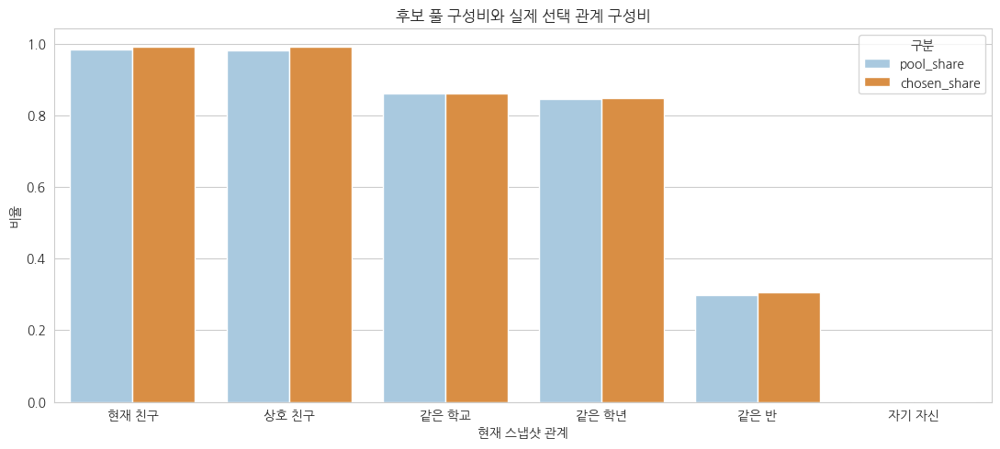

In [ ]:
# 후보 풀과 선택된 관계의 구성비
candidate_selection = con.execute("\nSELECT\n  '현재 친구' relation,\n  AVG(CAST(current_friend_any_direction_flag AS DOUBLE)) pool_share,\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN current_friend_any_direction_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0) chosen_share\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\nUNION ALL\nSELECT '상호 친구', AVG(CAST(current_friend_mutual_flag AS DOUBLE)),\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN current_friend_mutual_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\nUNION ALL\nSELECT '같은 학교', AVG(CAST(same_school_current_flag AS DOUBLE)),\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_current_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\nUNION ALL\nSELECT '같은 학년', AVG(CAST(same_school_grade_current_flag AS DOUBLE)),\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_grade_current_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\nUNION ALL\nSELECT '같은 반', AVG(CAST(same_school_grade_class_current_flag AS DOUBLE)),\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN same_school_grade_class_current_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\nUNION ALL\nSELECT '자기 자신', AVG(CAST(self_candidate_flag AS DOUBLE)),\n  SUM(CASE WHEN selected_candidate_canonical_pair_flag=1 THEN self_candidate_flag ELSE 0 END)\n    / NULLIF(SUM(selected_candidate_canonical_pair_flag),0)\nFROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\n").df()
candidate_selection['selection_enrichment_pp'] = (candidate_selection.chosen_share - candidate_selection.pool_share) * 100
display(candidate_selection)
fig, ax = plt.subplots(figsize=(11, 5))
plot_sel = candidate_selection.melt(id_vars='relation', value_vars=['pool_share', 'chosen_share'], var_name='구분', value_name='비율')
sns.barplot(data=plot_sel, x='relation', y='비율', hue='구분', ax=ax, palette=['#A0CBE8', '#F28E2B'])
ax.set_title('후보 풀 구성비와 실제 선택 관계 구성비')
ax.set_xlabel('현재 스냅샷 관계')
plt.tight_layout()
plt.show()
plt.close('all')


- 현재 친구는 후보 풀의 98.33%, 실제 선택의 99.23%를 차지했다.
- 선택에서 친구 비중이 조금 높지만, 애초에 주어진 후보 대부분이 친구였다.


In [ ]:
# 동일 사용자·후보 쌍의 반복 등장
pair_repetition = con.execute('\nSELECT CAST(resolved_owner_user_id AS VARCHAR) owner_user_id,\n       CAST(candidate_user_id AS VARCHAR) candidate_user_id,\n       COUNT(DISTINCT CAST(question_piece_id AS VARCHAR)) pieces_together,\n       MAX(CAST(current_friend_any_direction_flag AS INTEGER)) current_friend,\n       MAX(CAST(same_school_grade_class_current_flag AS INTEGER)) same_class,\n       MAX(CAST(self_candidate_flag AS INTEGER)) self_candidate\nFROM candidate\nWHERE analysis_eligible_candidate_canonical_flag=1\nGROUP BY 1,2\n').df()
pair_repetition['repeat_band'] = pd.cut(pair_repetition.pieces_together, [0, 1, 2, 5, 10, 20, 50, 100, np.inf], labels=['1', '2', '3-5', '6-10', '11-20', '21-50', '51-100', '101+'])
pair_rep_summary = pair_repetition.groupby('repeat_band', observed=True).agg(pairs=('candidate_user_id', 'size'), current_friend_rate=('current_friend', 'mean'), same_class_rate=('same_class', 'mean'), self_rate=('self_candidate', 'mean')).reset_index()
display(pair_rep_summary)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,repeat_band,pairs,current_friend_rate,same_class_rate,self_rate
0,1,17521,0.886650,0.162034,0.003424
1,2,15529,0.914225,0.172452,0.003606
2,3-5,39608,0.944102,0.179964,0.002474
3,6-10,53005,0.968946,0.203453,0.001717
4,11-20,68178,0.981270,0.239828,0.001291
5,21-50,63795,0.987899,0.296669,0.000988
6,51-100,13681,0.989986,0.379212,0.000439
7,101+,1765,0.988669,0.463456,0.000000


- 한 번 등장한 후보 쌍의 같은 반 비중은 16.20%, 101회 이상 등장한 쌍은 46.35%였다. 현재 친구 비중도 반복 구간이 높을수록 대체로 커졌다.
- 반복 후보에 가까운 관계가 많이 섞여 있어, 반복 횟수만의 선택 효과를 떼어 내기 어렵다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,relation_group,candidate_rows,row_selection_rate,selected_rows,pool_share,chosen_share,chosen_minus_pool_pp
0,1 자기 자신,4802,0.407955,1959.0,0.001007,0.001609,0.060205
1,2 상호 친구,4678934,0.257839,1206414.0,0.981107,0.990847,0.973997
2,3 단방향 친구,10604,0.164561,1745.0,0.002224,0.001433,-0.079031
3,4 같은 반 비친구,14628,0.110063,1610.0,0.003067,0.001322,-0.174497
4,5 같은 학년 비친구,42245,0.097432,4116.0,0.008858,0.003381,-0.547765
5,6 같은 학교 비친구,3732,0.086817,324.0,0.000783,0.000266,-0.051644
6,7 기타/현재 관계 미확인,14089,0.098659,1390.0,0.002954,0.001142,-0.181264


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,occurrence_band,candidate_rows,owners,observed_selection_rate,random_choice_baseline,lift_vs_random
0,1회,273082,4850,0.228254,0.255808,-0.027554
1,2회,255561,4819,0.222694,0.255682,-0.032988
2,3-5회,678740,4790,0.223801,0.255554,-0.031753
3,6-10회,889801,4639,0.234415,0.255414,-0.020999
4,11-20회,1132509,4336,0.250926,0.255227,-0.004301
5,21회+,1539341,3395,0.294705,0.255057,0.039648


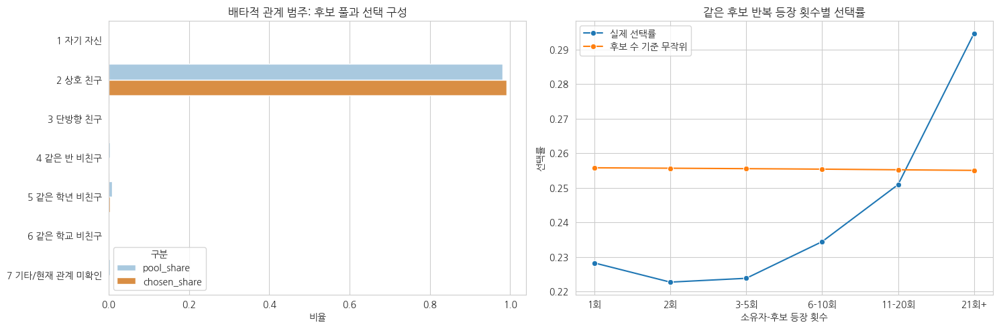

[후보 품질 분석 완료] 사용이 끝난 변수 25개 정리
[후보 품질 분석 완료] Python 사용 RAM 5.78 GB / 시스템 여유 RAM 6.69 GB


In [ ]:
# 관계 범주별 선택 · 후보 반복 횟수별 기준 비교
candidate_hierarchy = con.execute("\nWITH x AS (\n  SELECT selected_candidate_canonical_pair_flag selected,\n         CASE\n           WHEN self_candidate_flag=1 THEN '1 자기 자신'\n           WHEN current_friend_mutual_flag=1 THEN '2 상호 친구'\n           WHEN current_friend_any_direction_flag=1 THEN '3 단방향 친구'\n           WHEN same_school_grade_class_current_flag=1 THEN '4 같은 반 비친구'\n           WHEN same_school_grade_current_flag=1 THEN '5 같은 학년 비친구'\n           WHEN same_school_current_flag=1 THEN '6 같은 학교 비친구'\n           ELSE '7 기타/현재 관계 미확인' END relation_group\n  FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\n)\nSELECT relation_group, COUNT(*) candidate_rows,\n       AVG(CAST(selected AS DOUBLE)) row_selection_rate,\n       SUM(selected) selected_rows,\n       COUNT(*)/SUM(COUNT(*)) OVER() pool_share,\n       SUM(selected)/SUM(SUM(selected)) OVER() chosen_share\nFROM x GROUP BY 1 ORDER BY 1\n").df()
candidate_hierarchy['chosen_minus_pool_pp'] = (candidate_hierarchy.chosen_share - candidate_hierarchy.pool_share) * 100
display(candidate_hierarchy)
candidate_occurrence = con.execute("\nWITH base AS (\n  SELECT CAST(resolved_owner_user_id AS VARCHAR) owner_user_id,\n         CAST(candidate_user_id AS VARCHAR) candidate_user_id,\n         CAST(question_piece_id AS VARCHAR) question_piece_id,\n         TRY_CAST(candidate_source_created_at AS TIMESTAMP) created_at,\n         CAST(selected_candidate_canonical_pair_flag AS INTEGER) selected,\n         CAST(candidate_count_canonical_per_piece AS DOUBLE) candidate_count,\n         ROW_NUMBER() OVER(\n           PARTITION BY CAST(resolved_owner_user_id AS VARCHAR),CAST(candidate_user_id AS VARCHAR)\n           ORDER BY TRY_CAST(candidate_source_created_at AS TIMESTAMP),CAST(question_piece_id AS VARCHAR)\n         ) pair_occurrence\n  FROM candidate WHERE analysis_eligible_candidate_canonical_flag=1\n), banded AS (\n  SELECT *,CASE WHEN pair_occurrence=1 THEN '1회'\n                WHEN pair_occurrence=2 THEN '2회'\n                WHEN pair_occurrence<=5 THEN '3-5회'\n                WHEN pair_occurrence<=10 THEN '6-10회'\n                WHEN pair_occurrence<=20 THEN '11-20회'\n                ELSE '21회+' END occurrence_band\n  FROM base\n)\nSELECT occurrence_band, COUNT(*) candidate_rows, COUNT(DISTINCT owner_user_id) owners,\n       AVG(CAST(selected AS DOUBLE)) observed_selection_rate,\n       AVG(1.0/NULLIF(candidate_count,0)) random_choice_baseline,\n       AVG(CAST(selected AS DOUBLE)-1.0/NULLIF(candidate_count,0)) lift_vs_random\nFROM banded GROUP BY 1\nORDER BY CASE occurrence_band WHEN '1회' THEN 1 WHEN '2회' THEN 2 WHEN '3-5회' THEN 3 WHEN '6-10회' THEN 4 WHEN '11-20회' THEN 5 ELSE 6 END\n").df()
display(candidate_occurrence)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
hier_plot = candidate_hierarchy.melt(id_vars='relation_group', value_vars=['pool_share', 'chosen_share'], var_name='구분', value_name='비율')
sns.barplot(data=hier_plot, y='relation_group', x='비율', hue='구분', ax=ax[0], palette=['#A0CBE8', '#F28E2B'])
ax[0].set(title='배타적 관계 범주: 후보 풀과 선택 구성', xlabel='비율', ylabel='')
sns.lineplot(data=candidate_occurrence, x='occurrence_band', y='observed_selection_rate', marker='o', label='실제 선택률', ax=ax[1])
sns.lineplot(data=candidate_occurrence, x='occurrence_band', y='random_choice_baseline', marker='o', label='후보 수 기준 무작위', ax=ax[1])
ax[1].set(title='같은 후보 반복 등장 횟수별 선택률', xlabel='소유자-후보 등장 횟수', ylabel='선택률')
plt.tight_layout()
plt.show()
team7_release_unused('215', '후보 품질 분석 완료')
plt.close('all')


- 상호 친구가 후보 행의 98.11%, 선택 행의 99.08%를 차지했다.
- 21회 이상 등장한 후보의 선택률은 균등 무작위 선택 계산값보다 3.96%p 높았다. 실제 추천 실험 결과가 아니라 후보별 동일 확률을 가정한 비교다.


### 3-3-4. 콘텐츠 특성과 투표 기록의 관계

- 반복·테마·질문 위치·문구 길이별 차이를 학교·기간·이용량과 함께 살펴봤다. 아래 검정과 모형은 관측된 관계를 요약한 것으로, 특정 콘텐츠를 바꿨을 때의 효과까지 추정하지는 못한다.


In [ ]:
# 질문 반복 여부와 투표 기록률 차이
def wilson_ci(k, n, alpha=0.05):
    if n == 0:
        return (np.nan, np.nan)
    z = stats.norm.ppf(1 - alpha / 2)
    p = k / n
    den = 1 + z * z / n
    ctr = (p + z * z / (2 * n)) / den
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (ctr - half, ctr + half)

def binary_compare(df, group, outcome):
    tab = pd.crosstab(df[group], df[outcome]).reindex(index=[0, 1], columns=[0, 1], fill_value=0)
    chi2, p, _, _ = stats.chi2_contingency(tab)
    n = tab.values.sum()
    v = math.sqrt(chi2 / n) if n else np.nan
    a, b = (tab.loc[1, 1], tab.loc[1, 0])
    c, d = (tab.loc[0, 1], tab.loc[0, 0])
    odds = (a + 0.5) * (d + 0.5) / ((b + 0.5) * (c + 0.5))
    rates = []
    for g in [0, 1]:
        k = int(tab.loc[g, 1])
        total = int(tab.loc[g].sum())
        lo, hi = wilson_ci(k, total)
        rates.append((g, total, k, k / total if total else np.nan, lo, hi))
    return (tab, {'feature': group, 'outcome': outcome, 'rate_0': rates[0][3], 'rate_1': rates[1][3], 'absolute_diff': rates[1][3] - rates[0][3], 'odds_ratio': odds, 'cramers_v': v, 'p_value': p})
tests = []
for feature, outcome in [('repeat_question_id', 'vote_record_exists'), ('repeat_exact_text', 'vote_record_exists'), ('repeat_semantic_090', 'vote_record_exists')]:
    _, result = binary_compare(piece, feature, outcome)
    tests.append(result)
tests = pd.DataFrame(tests)
tests['p_fdr_bh'] = multipletests(tests.p_value, method='fdr_bh')[1]
display(tests.sort_values('outcome'))


,feature,outcome,rate_0,rate_1,absolute_diff,odds_ratio,cramers_v,p_value,p_fdr_bh
0,repeat_question_id,vote_record_exists,0.957938,0.980603,0.022665,2.219580,0.046119,0.0,0.0
1,repeat_exact_text,vote_record_exists,0.958059,0.979479,0.021420,2.089307,0.044043,0.0,0.0
2,repeat_semantic_090,vote_record_exists,0.957939,0.978533,0.020594,2.001309,0.043450,0.0,0.0


- 의미 반복 질문의 투표 기록률은 97.85%, 비반복 질문은 95.79%로 약 2.06%p 차이였다. ID·문구 기준도 비슷한 방향이었다.
- 통계적으로는 유의했지만 Cramér’s V는 0.043~0.046으로 작았다. 큰 표본에서 드러난 작은 차이다.


,theme_id,rows,unique_texts,users,vote_rate,skip_history_rate,candidate_source_observed_rate,semantic_repeat_rate,top_terms
0,0,86491,410,4770,0.950342,0.001133,0.950342,0.146038,사람 / 같 / 것 / 잘 / 친구 / 이 / 어울리 / 하 / 있 / 나
4,4,199138,831,4924,0.953590,0.001115,0.953620,0.169114,친구 / 같 / 것 / 싶 / 가장 / 하 / 같이 / 주 / 있 / 잘
5,5,91753,405,4809,0.955173,0.000774,0.955228,0.170000,것 / 같 / 사람 / 안 / 하 / 못 / 먹 / 있 / 가장 / 보
3,3,186627,550,4906,0.962722,0.000857,0.962749,0.220997,것 / 같 / 사람 / 하 / 이 / 있 / 잘 / 가 / 되 / 수
1,1,318391,838,4961,0.964946,0.000901,0.964971,0.210122,사람 / 싶 / 같 / 것 / 같이 / 하 / 주 / 보 / 나 / 있
2,2,383076,864,4961,0.968283,0.000754,0.968301,0.229046,가장 / 사람 / 잘 / 같 / 것 / 제일 / 어울리 / 하 / 이 / 좋


,question_position,rows,users,vote_rate,skip_history_rate,semantic_repeat_rate,candidate_source_observed_rate
0,1,129160,4972,0.965678,0.002214,0.202772,0.965732
1,2,128221,4970,0.964163,0.001997,0.202736,0.964202
2,3,127481,4972,0.963336,0.001483,0.204085,0.963430
3,4,127041,4972,0.962658,0.001071,0.201880,0.962681
4,5,126714,4971,0.961962,0.000718,0.204113,0.961977
5,6,126001,4972,0.961302,0.000460,0.204919,0.961310
6,7,125895,4972,0.960975,0.000342,0.201573,0.960983
7,8,125035,4972,0.960507,0.000216,0.203647,0.960507
8,9,124433,4972,0.960163,0.000137,0.206047,0.960163
9,10,125495,4972,0.960413,0.000191,0.205434,0.960413


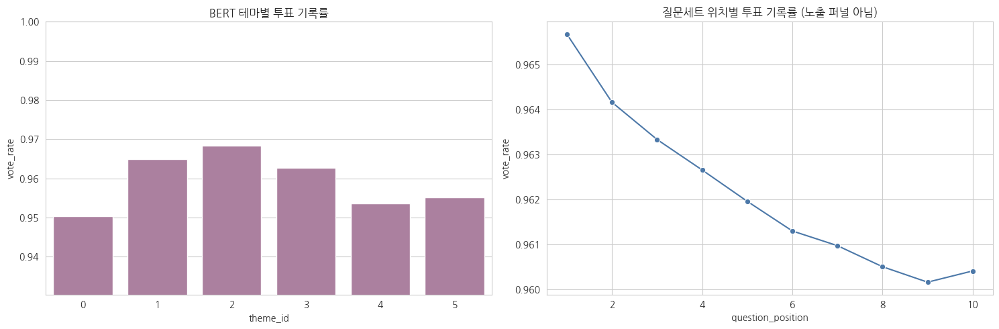

In [ ]:
# 테마·질문 위치별 투표 기록
theme_behavior = piece.groupby('theme_id').agg(rows=('question_piece_id', 'size'), unique_texts=('question_text_normalized', 'nunique'), users=('owner_user_id', 'nunique'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean'), candidate_source_observed_rate=('candidate_source_observed', 'mean'), semantic_repeat_rate=('repeat_semantic_090', 'mean')).reset_index().merge(theme_summary[['theme_id', 'top_terms']], on='theme_id', how='left')
display(theme_behavior.sort_values('vote_rate'))
position_behavior = piece.dropna(subset=['question_position']).groupby('question_position').agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), vote_rate=('vote_record_exists', 'mean'), skip_history_rate=('raw_is_skipped', 'mean'), semantic_repeat_rate=('repeat_semantic_090', 'mean'), candidate_source_observed_rate=('candidate_source_observed', 'mean')).reset_index()
display(position_behavior)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=theme_behavior, x='theme_id', y='vote_rate', color='#B279A2', ax=ax[0])
ax[0].set_title('BERT 테마별 투표 기록률')
ax[0].set_ylim(max(0, theme_behavior.vote_rate.min() - 0.02), 1)
sns.lineplot(data=position_behavior, x='question_position', y='vote_rate', marker='o', color='#4C78A8', ax=ax[1])
ax[1].set_title('질문세트 위치별 투표 기록률 (노출 퍼널 아님)')
plt.tight_layout()
plt.show()
plt.close('all')


- 6개 테마의 투표 기록률은 약 95.03~96.83%였다.
- 질문 위치별로는 1번 96.57%, 10번 96.04%였다. 실제 노출이 아니라 생성된 질문조각 기준이다.


In [ ]:
# 테마 차이 검정 · 질문 위치 추세 · 문구 길이
theme_tab = pd.crosstab(piece.theme_id, piece.vote_record_exists)
theme_chi2, theme_p, _, _ = stats.chi2_contingency(theme_tab)
theme_v = np.sqrt(theme_chi2 / (theme_tab.values.sum() * min(theme_tab.shape[0] - 1, theme_tab.shape[1] - 1)))
theme_test = pd.DataFrame([{'chi2': theme_chi2, 'df': (theme_tab.shape[0] - 1) * (theme_tab.shape[1] - 1), 'p_value': theme_p, 'cramers_v': theme_v, 'max_min_rate_diff': theme_behavior.vote_rate.max() - theme_behavior.vote_rate.min()}])
theme_ci = []
for _, r in theme_behavior.iterrows():
    k = int(round(r.vote_rate * r.rows))
    lo, hi = wilson_ci(k, int(r.rows))
    theme_ci.append({'theme_id': int(r.theme_id), 'rows': int(r.rows), 'vote_rate': r.vote_rate, 'ci95_low': lo, 'ci95_high': hi, 'top_terms': r.top_terms})
theme_ci = pd.DataFrame(theme_ci)
display(theme_test)
display(theme_ci.sort_values('vote_rate'))
position_trends = []
for label, sub in [('전체', piece), ('2023-05', piece[piece.is_2023_may.eq(1)]), ('기타 기간', piece[piece.is_2023_may.eq(0)])]:
    agg = sub.dropna(subset=['question_position']).groupby('question_position').vote_record_exists.agg(['sum', 'count']).reset_index()
    endog = np.column_stack([agg['sum'], agg['count'] - agg['sum']])
    fit = sm.GLM(endog, sm.add_constant(agg.question_position.astype(float)), family=sm.families.Binomial()).fit()
    beta = float(fit.params.iloc[1])
    se = float(fit.bse.iloc[1])
    position_trends.append({'scope': label, 'rows': int(agg['count'].sum()), 'odds_ratio_per_position': np.exp(beta), 'ci95_low': np.exp(beta - 1.96 * se), 'ci95_high': np.exp(beta + 1.96 * se), 'p_value': float(fit.pvalues.iloc[1])})
position_trends = pd.DataFrame(position_trends)
piece['text_length_band'] = pd.qcut(piece.text_len, 10, duplicates='drop')
length_behavior = piece.groupby('text_length_band', observed=True).agg(rows=('question_piece_id', 'size'), median_length=('text_len', 'median'), vote_rate=('vote_record_exists', 'mean'), semantic_repeat_rate=('repeat_semantic_090', 'mean')).reset_index()
display(position_trends)
display(length_behavior)


,chi2,df,p_value,cramers_v,max_min_rate_diff
0,1319.625665,5,3.576100e-283,0.032292,0.017941


,theme_id,rows,vote_rate,ci95_low,ci95_high,top_terms
0,0,86491,0.950342,0.948874,0.951770,사람 / 같 / 것 / 잘 / 친구 / 이 / 어울리 / 하 / 있 / 나
4,4,199138,0.953590,0.952657,0.954505,친구 / 같 / 것 / 싶 / 가장 / 하 / 같이 / 주 / 있 / 잘
5,5,91753,0.955173,0.953815,0.956493,것 / 같 / 사람 / 안 / 하 / 못 / 먹 / 있 / 가장 / 보
3,3,186627,0.962722,0.961853,0.963572,것 / 같 / 사람 / 하 / 이 / 있 / 잘 / 가 / 되 / 수
1,1,318391,0.964946,0.964301,0.965579,사람 / 싶 / 같 / 것 / 같이 / 하 / 주 / 보 / 나 / 있
2,2,383076,0.968283,0.967723,0.968833,가장 / 사람 / 잘 / 같 / 것 / 제일 / 어울리 / 하 / 이 / 좋


,scope,rows,odds_ratio_per_position,ci95_low,ci95_high,p_value
0,전체,1265476,0.984242,0.981121,0.987373,1.100630e-22
1,2023-05,1144964,0.982476,0.978453,0.986515,3.020865e-17
2,기타 기간,120512,0.984912,0.979679,0.990173,2.226410e-08


,text_length_band,rows,median_length,vote_rate,semantic_repeat_rate
0,"(2.999, 12.0]",142036,11.0,0.961827,0.225943
1,"(12.0, 14.0]",148102,14.0,0.963559,0.210267
2,"(14.0, 16.0]",140158,16.0,0.957370,0.183828
3,"(16.0, 17.0]",97742,17.0,0.960478,0.197448
4,"(17.0, 19.0]",183790,19.0,0.960194,0.192845
5,"(19.0, 20.0]",95925,20.0,0.962022,0.198728
6,"(20.0, 21.0]",110608,21.0,0.966196,0.246366
7,"(21.0, 23.0]",141716,23.0,0.964951,0.204726
8,"(23.0, 26.0]",105762,25.0,0.960789,0.182551
9,"(26.0, 45.0]",99637,28.0,0.965384,0.194908


- 테마 간 최대 차이는 약 1.79%p, Cramér’s V는 0.032였다. 질문 위치가 한 칸 뒤로 갈 때의 투표 기록 오즈비는 0.984였다.
- 문구 길이에 따른 증가·감소 패턴은 일정하지 않았다.


,model,train_rows,test_rows,temporal_cutoff,roc_auc,average_precision,log_loss,brier_score,test_positive_rate,roc_auc_delta_vs_baseline,average_precision_delta_vs_baseline,log_loss_delta_vs_baseline,brier_score_delta_vs_baseline
0,1_baseline,1012373,253103,2023-05-24 08:02:38,0.818036,0.970392,0.757058,0.133570,0.886074,0.000000,0.000000,0.000000,0.000000
1,2_plus_text_theme,1012373,253103,2023-05-24 08:02:38,0.817522,0.970242,0.744835,0.131238,0.886074,-0.000514,-0.000149,-0.012223,-0.002332
2,3_plus_repeat,1012373,253103,2023-05-24 08:02:38,0.817179,0.970209,0.745603,0.131886,0.886074,-0.000857,-0.000183,-0.011455,-0.001685


,feature,coef_log_odds,odds_ratio_per_scaled_unit
11,cat__school_id_4426,2.287458,9.849869
16,cat__month_2023-04,2.003661,7.416156
15,cat__school_id_5520,1.290411,3.634278
0,num__user_piece_sequence,0.892423,2.441036
17,cat__month_2023-05,0.891186,2.438018
1,num__signup_elapsed_days,-0.868500,0.419580
6,cat__school_id_1478,0.681049,1.975950
9,cat__school_id_352,-0.578444,0.560770
21,cat__theme_id_3,0.545759,1.725918
20,cat__theme_id_2,0.537586,1.711869


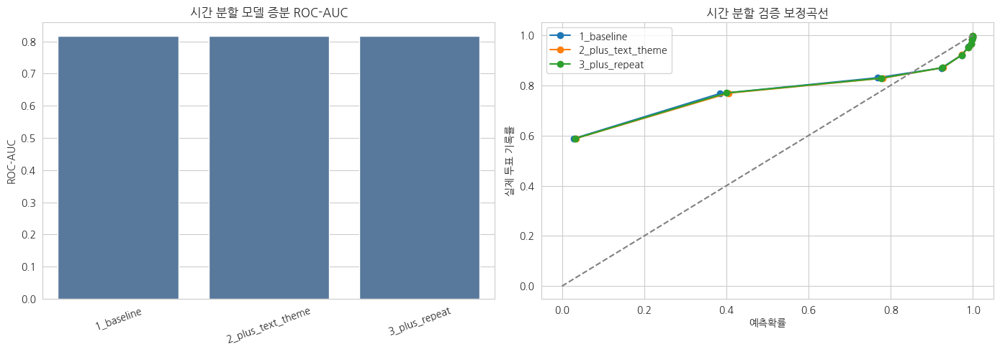

In [ ]:
# 시간 분할 모형 · 텍스트·반복 변수 추가 비교
model_cols = ['vote_record_exists', 'piece_created_at', 'text_len', 'repeat_exact_text', 'repeat_semantic_090', 'user_piece_sequence', 'signup_elapsed_days', 'question_position', 'school_id', 'month', 'theme_id']
model_df = piece[model_cols].copy().sort_values('piece_created_at')
temporal_cutoff = model_df.piece_created_at.quantile(0.8)
train = model_df[model_df.piece_created_at < temporal_cutoff].copy()
test = model_df[model_df.piece_created_at >= temporal_cutoff].copy()
specs = {'1_baseline': {'num': ['user_piece_sequence', 'signup_elapsed_days', 'question_position'], 'cat': ['school_id', 'month']}, '2_plus_text_theme': {'num': ['user_piece_sequence', 'signup_elapsed_days', 'question_position', 'text_len'], 'cat': ['school_id', 'month', 'theme_id']}, '3_plus_repeat': {'num': ['user_piece_sequence', 'signup_elapsed_days', 'question_position', 'text_len', 'repeat_exact_text', 'repeat_semantic_090'], 'cat': ['school_id', 'month', 'theme_id']}}
model_rows = []
fitted = {}
predictions = {}
for model_name, spec in specs.items():
    pre = ColumnTransformer([('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), spec['num']), ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), spec['cat'])])
    clf = Pipeline([('pre', pre), ('model', LogisticRegression(max_iter=500, C=0.5, solver='liblinear'))])
    features = spec['num'] + spec['cat']
    clf.fit(train[features], train.vote_record_exists)
    pred = clf.predict_proba(test[features])[:, 1]
    fitted[model_name] = clf
    predictions[model_name] = pred
    model_rows.append({'model': model_name, 'train_rows': len(train), 'test_rows': len(test), 'temporal_cutoff': test.piece_created_at.min(), 'roc_auc': roc_auc_score(test.vote_record_exists, pred), 'average_precision': average_precision_score(test.vote_record_exists, pred), 'log_loss': log_loss(test.vote_record_exists, pred), 'brier_score': brier_score_loss(test.vote_record_exists, pred), 'test_positive_rate': test.vote_record_exists.mean()})
model_perf = pd.DataFrame(model_rows)
for metric in ['roc_auc', 'average_precision', 'log_loss', 'brier_score']:
    model_perf[f'{metric}_delta_vs_baseline'] = model_perf[metric] - model_perf.loc[0, metric]
display(model_perf)
best_name = '3_plus_repeat'
clf = fitted[best_name]
feature_names = clf.named_steps['pre'].get_feature_names_out()
coef = clf.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef_log_odds': coef, 'odds_ratio_per_scaled_unit': np.exp(coef)})
display(coef_df.reindex(coef_df.coef_log_odds.abs().sort_values(ascending=False).index).head(30))
calibration = []
for name, pred in predictions.items():
    bins = pd.qcut(pred, 10, duplicates='drop')
    d = pd.DataFrame({'pred': pred, 'actual': test.vote_record_exists.values, 'bin': bins})
    c = d.groupby('bin', observed=True).agg(mean_pred=('pred', 'mean'), observed_rate=('actual', 'mean'), rows=('actual', 'size')).reset_index(drop=True)
    c['model'] = name
    calibration.append(c)
calibration = pd.concat(calibration, ignore_index=True)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=model_perf, x='model', y='roc_auc', color='#4C78A8', ax=ax[0])
ax[0].set(title='시간 분할 모델 증분 ROC-AUC', xlabel='', ylabel='ROC-AUC')
ax[0].tick_params(axis='x', rotation=20)
for name, g in calibration.groupby('model'):
    ax[1].plot(g.mean_pred, g.observed_rate, marker='o', label=name)
ax[1].plot([0, 1], [0, 1], '--', color='gray')
ax[1].set(title='시간 분할 검증 보정곡선', xlabel='예측확률', ylabel='실제 투표 기록률')
ax[1].legend()
plt.tight_layout()
plt.show()
plt.close('all')


- ROC-AUC는 기준모형 0.8180, 텍스트·테마 추가 0.8175, 반복까지 추가 0.8172였다.
- 기준모형보다 로그 손실은 조금 줄었지만 ROC-AUC 개선은 없었다.


In [ ]:
# 기간·완전 세트·반복 정의별 재검증
complete_qsets = set(con.execute('SELECT CAST(question_set_id AS VARCHAR) FROM qset\nWHERE analysis_eligible_question_set_flag=1 AND complete_10_piece_reference_flag=1').df().iloc[:, 0])
piece['complete_10_piece_set'] = piece.question_set_id.isin(complete_qsets).astype(int)
robust = []
for label, sub in [('전체', piece), ('2023-05', piece[piece.is_2023_may == 1]), ('기타 기간', piece[piece.is_2023_may == 0]), ('10개 참조 완전 세트', piece[piece.complete_10_piece_set == 1])]:
    for definition in ['repeat_question_id', 'repeat_exact_text', 'repeat_semantic_090']:
        if sub[definition].nunique() < 2:
            continue
        _, r = binary_compare(sub, definition, 'vote_record_exists')
        robust.append({'scope': label, 'repeat_definition': definition, 'rows': len(sub), 'rate_nonrepeat': r['rate_0'], 'rate_repeat': r['rate_1'], 'absolute_diff': r['absolute_diff'], 'odds_ratio': r['odds_ratio'], 'cramers_v': r['cramers_v'], 'p_value': r['p_value']})
robust = pd.DataFrame(robust)
display(robust)


,scope,repeat_definition,rows,rate_nonrepeat,rate_repeat,absolute_diff,odds_ratio,cramers_v,p_value
0,전체,repeat_question_id,1265476,0.957938,0.980603,0.022665,2.219580,0.046119,0.000000e+00
1,전체,repeat_exact_text,1265476,0.958059,0.979479,0.021420,2.089307,0.044043,0.000000e+00
2,전체,repeat_semantic_090,1265476,0.957939,0.978533,0.020594,2.001309,0.043450,0.000000e+00
3,2023-05,repeat_question_id,1144964,0.973489,0.982684,0.009194,1.545261,0.023326,1.694799e-137
4,2023-05,repeat_exact_text,1144964,0.973498,0.982443,0.008946,1.523240,0.022891,1.700293e-132
5,2023-05,repeat_semantic_090,1144964,0.973402,0.982239,0.008837,1.510970,0.023169,1.119139e-135
6,기타 기간,repeat_question_id,120512,0.822931,0.947857,0.124926,3.908913,0.108459,3.094805e-310
7,기타 기간,repeat_exact_text,120512,0.823002,0.936071,0.113068,3.147595,0.102254,5.440480e-276
8,기타 기간,repeat_semantic_090,120512,0.822558,0.926754,0.104196,2.728481,0.098788,9.555446e-258
9,10개 참조 완전 세트,repeat_question_id,571190,0.904958,0.960869,0.055911,2.578638,0.081154,0.000000e+00


- ID·문구·의미군 어느 기준에서도 단순 집계의 반복군 투표 기록률이 더 높았다.
- 5월과 그 외 기간, 질문조각 10개가 연결된 세트를 따로 보면 차이의 크기가 달라졌다.


In [ ]:
# 질문 공급·반복·후보 분석 결과 정리
repeat_effect = float(tests.query("feature=='repeat_semantic_090' and outcome=='vote_record_exists'").absolute_diff.iloc[0])
theme_range = float(theme_behavior.vote_rate.max() - theme_behavior.vote_rate.min())
candidate_obs_vote = float(candidate_observed.vote_record_exists.mean())
content_auc_gain = float(model_perf.loc[model_perf.model == '3_plus_repeat', 'roc_auc'].iloc[0] - model_perf.loc[model_perf.model == '1_baseline', 'roc_auc'].iloc[0])
content_logloss_gain = float(model_perf.loc[model_perf.model == '3_plus_repeat', 'log_loss'].iloc[0] - model_perf.loc[model_perf.model == '1_baseline', 'log_loss'].iloc[0])
position_or = float(position_trends.loc[position_trends.scope == '전체', 'odds_ratio_per_position'].iloc[0])
within_user_repeat = float(within_user_result.mean_within_user_diff.iloc[0])
stratified_repeat = float(stratified_result.adjusted_rate_diff.iloc[0])
candidate_repeat_lift = float(candidate_occurrence.loc[candidate_occurrence.occurrence_band == '21회+', 'lift_vs_random'].iloc[0])
evidence_review = pd.DataFrame([{'분석질문': '질문 공급이 계속 갱신됐는가', '확인된 사실': f"2023-05 신규 문구 비율 {new_monthly.loc[new_monthly.month == '2023-05', 'new_text_share'].iloc[0]:.1%}, 2023-07 이후 거의 0%", '판정': '공급 신규성 약화 관측', '말할 수 없는 것': '후기 월 표본이 매우 작으므로 전체 사용자 경험의 감소 원인이라고 단정'}, {'분석질문': '반복이 참여를 낮췄는가', '확인된 사실': f'단순 {repeat_effect:+.2%}p, 사용자 내부 {within_user_repeat:+.2%}p, 층화 통제 {stratified_repeat:+.2%}p', '판정': '통제 방식에 따라 방향이 바뀜. 반복에 의한 참여 저하 미확정', '말할 수 없는 것': '반복이 이탈을 일으켰다는 인과 주장'}, {'분석질문': '후보 관계가 투표를 만들었는가', '확인된 사실': f'후보 원천 관측 질문의 투표 기록 보유율 {candidate_obs_vote:.3%}', '판정': '효과 식별 불가. 후보 풀과 선택 구성만 기술', '말할 수 없는 것': '친구 후보 때문에 투표율이 높아졌다는 주장'}, {'분석질문': '같은 후보가 반복 선택됐는가', '확인된 사실': f'동일 소유자-후보 21회 이상 등장 시 무작위 기준 대비 선택률 {candidate_repeat_lift:+.2%}p', '판정': '반복 노출과 선택 집중의 연관 관측', '말할 수 없는 것': '반복 노출이 선호를 만들었다는 인과 주장'}, {'분석질문': '질문 테마별 행동이 달랐는가', '확인된 사실': f'테마 차이 {theme_range:.2%}p, Cramér V {theme_v:.3f}, 시드 평균 ARI {theme_stability.adjusted_rand_index.mean():.3f}', '판정': '행동 차이는 작고 군집 안정성도 낮아 탐색 결과로 사용', '말할 수 없는 것': '테마가 고정된 정답 분류이거나 행동 차이의 원인이라는 주장'}, {'분석질문': '뒤 위치에서 참여가 줄었는가', '확인된 사실': f'위치 1 증가당 투표 기록 오즈비 {position_or:.4f}', '판정': '생성 위치와 투표 기록의 추세만 확인', '말할 수 없는 것': '실제 화면 퍼널의 위치별 이탈'}, {'분석질문': '콘텐츠 변수가 예측력을 더했는가', '확인된 사실': f'ROC-AUC 증분 {content_auc_gain:+.4f}, log loss 변화 {content_logloss_gain:+.4f}', '판정': '순위 예측 증분은 거의 없고 확률 오차는 소폭 개선', '말할 수 없는 것': '예측변수가 제품 개편의 인과 레버라는 주장'}])
display(evidence_review)


,분석질문,확인된 사실,판정,말할 수 없는 것
0,질문 공급이 계속 갱신됐는가,"2023-05 신규 문구 비율 85.0%, 2023-07 이후 거의 0%",공급 신규성 약화 관측,후기 월 표본이 매우 작으므로 전체 사용자 경험의 감소 원인이라고 단정
1,반복이 참여를 낮췄는가,"단순 +2.06%p, 사용자 내부 -1.14%p, 층화 통제 +1.08%p",통제 방식에 따라 방향이 바뀜. 반복에 의한 참여 저하 미확정,반복이 이탈을 일으켰다는 인과 주장
2,후보 관계가 투표를 만들었는가,후보 원천 관측 질문의 투표 기록 보유율 99.997%,효과 식별 불가. 후보 풀과 선택 구성만 기술,친구 후보 때문에 투표율이 높아졌다는 주장
3,같은 후보가 반복 선택됐는가,동일 소유자-후보 21회 이상 등장 시 무작위 기준 대비 선택률 +3.96%p,반복 노출과 선택 집중의 연관 관측,반복 노출이 선호를 만들었다는 인과 주장
4,질문 테마별 행동이 달랐는가,"테마 차이 1.79%p, Cramér V 0.032, 시드 평균 ARI 0.387",행동 차이는 작고 군집 안정성도 낮아 탐색 결과로 사용,테마가 고정된 정답 분류이거나 행동 차이의 원인이라는 주장
5,뒤 위치에서 참여가 줄었는가,위치 1 증가당 투표 기록 오즈비 0.9842,생성 위치와 투표 기록의 추세만 확인,실제 화면 퍼널의 위치별 이탈
6,콘텐츠 변수가 예측력을 더했는가,"ROC-AUC 증분 -0.0009, log loss 변화 -0.0115",순위 예측 증분은 거의 없고 확률 오차는 소폭 개선,예측변수가 제품 개편의 인과 레버라는 주장


- 여기까지는 새 문구 공급 감소와 후보 선택의 집중이 눈에 띈다. 반면 반복 질문의 투표 기록률은 낮지 않았다. 다음에는 투표 한 번을 넘어 이후 질문 이용까지 이어졌는지 살펴봤다.


In [ ]:
# Content 기초 분석 정합성 점검
qa = []

def qa_add(name, ok, detail):
    qa.append({'check': name, 'status': 'PASS' if ok else 'FAIL', 'detail': detail})
qa_add('정제 질문조각 전행 적재', len(piece) == int(scope.loc[scope.mart == 'question_piece', 'rows_eligible'].iloc[0]), f'{len(piece):,}')
qa_add('질문 문구 100% 연결', piece.question_text.notna().all(), f'missing={piece.question_text.isna().sum():,}')
qa_add('질문조각 ID 유일', piece.question_piece_id.is_unique, f'duplicates={piece.question_piece_id.duplicated().sum():,}')
qa_add('관측 후보 수 비음수', (candidate_observed.candidate_count >= 0).all(), f'min={candidate_observed.candidate_count.min()}')
qa_add('후보 미관측을 0명으로 대체하지 않음', piece.loc[piece.candidate_source_observed.eq(0), 'candidate_count'].isna().all(), f'unobserved={int((piece.candidate_source_observed == 0).sum()):,}')
qa_add('투표 플래그 이진', set(piece.vote_record_exists.dropna().unique()) <= {0, 1}, str(sorted(piece.vote_record_exists.unique())))
qa_add('테마 전행 할당', piece.theme_id.notna().all(), f'missing={piece.theme_id.isna().sum():,}')
qa_add('의미군 전행 할당', piece.semantic_group_090.notna().all(), f'missing={piece.semantic_group_090.isna().sum():,}')
qa_add('시간순 검증 완전 분리', train.piece_created_at.max() < test.piece_created_at.min(), f'{train.piece_created_at.max()} < {test.piece_created_at.min()}')
qa_add('테마 시드 안정성 계산', theme_stability.adjusted_rand_index.notna().all(), f'mean_ARI={theme_stability.adjusted_rand_index.mean():.3f}')
qa_add('모델 증분 비교 3종', len(model_perf) == 3, f'models={len(model_perf)}')
qa_add('주장 경계 7개 기록', len(evidence_review) == 7, f'rows={len(evidence_review)}')
qa_df = pd.DataFrame(qa)
display(qa_df)
assert (qa_df.status == 'PASS').all(), qa_df
run_manifest = {'model': MODEL_NAME, 'random_state': RANDOM_STATE, 'rows': len(piece), 'users': int(piece.owner_user_id.nunique()), 'schools': int(piece.school_id.nunique()), 'period': [str(piece.piece_created_at.min()), str(piece.piece_created_at.max())], 'best_theme_k': best_k, 'semantic_thresholds': [0.85, 0.9, 0.95], 'important_caveats': ['piece_created_at is not confirmed exposure time', 'F is not interpreted as completion', 'friend/school/grade/class are current snapshots', 'candidate source is almost conditional on vote record', 'associations are not causal']}
print('FINAL QA: PASS', len(qa_df), '/ FAIL 0')
team7_release_unused('227', 'Content 기본 분석 완료')


,check,status,detail
0,정제 질문조각 전행 적재,PASS,"1,265,476"
1,질문 문구 100% 연결,PASS,missing=0
2,질문조각 ID 유일,PASS,duplicates=0
3,관측 후보 수 비음수,PASS,min=1
4,후보 미관측을 0명으로 대체하지 않음,PASS,"unobserved=47,887"
5,투표 플래그 이진,PASS,"[np.int32(0), np.int32(1)]"
6,테마 전행 할당,PASS,missing=0
7,의미군 전행 할당,PASS,missing=0
8,시간순 검증 완전 분리,PASS,2023-05-24 08:02:20 < 2023-05-24 08:02:38
9,테마 시드 안정성 계산,PASS,mean_ARI=0.387


FINAL QA: PASS 12 / FAIL 0
[Content 기본 분석 완료] 사용이 끝난 변수 31개 정리
[Content 기본 분석 완료] Python 사용 RAM 5.07 GB / 시스템 여유 RAM 7.08 GB


- 문구 연결·질문조각 ID 중복·테마 배정·학습 및 평가 시점 분리 점검을 통과했다.


### 3-3-5. 콘텐츠 반복 이후의 다음 질문 이용

- 세트별 반복률과 다양성을 묶은 소진지수로 다음 세트 생성을 비교했다. 이 지수는 실제 지루함을 측정한 설문값과는 다르다.
- 다음 세트 생성에는 같은 방문에서 연달아 질문을 푼 경우도 포함된다. 사용자 내부 변화와 사용자 간 차이를 나눠 살펴봤다.


In [ ]:
# 후속 행동 분석 데이터 · 집계 함수 준비
FOLLOWUP_DIR = OUTPUT_DIR / 'followup'
FOLLOWUP_FIG_DIR = FOLLOWUP_DIR / 'figures'
DATA_PROCESSED = Path(globals().get('PREPROCESSED_ROOT', '/content/team7_processed'))
FRIEND_PATH = DATA_PROCESSED / 'viral_school' / 'mart_friend_request_event_v2_clean.csv.gz'
SCHOOL_DAILY_PATH = DATA_PROCESSED / 'viral_school' / 'mart_school_viral_daily_v2_clean.csv.gz'
USER_VIRAL_PATH = DATA_PROCESSED / 'viral_school' / 'mart_user_viral_profile_v2_clean.csv.gz'
VOTE_PATH = DATA_PROCESSED / 'question_candidate' / 'mart_vote_record_v2_clean.csv.gz'

def show_save(df, name, head=None):
    display(df if head is None else df.head(head))

def zscore(series):
    series = pd.to_numeric(series, errors='coerce')
    standard_deviation = series.std(ddof=0)
    return (series - series.mean()) / standard_deviation if pd.notna(standard_deviation) and standard_deviation > 0 else series * 0

def entropy_from_counts(row):
    values = np.asarray(row, dtype=float)
    values = values[values > 0]
    if len(values) <= 1:
        return 0.0
    probabilities = values / values.sum()
    return float(-(probabilities * np.log(probabilities)).sum() / np.log(len(values)))
print('Content 후속 분석 준비 완료')


Content 후속 분석 준비 완료


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,exhaustion_decile,qsets,users,exhaustion_index,repeat_rate,theme_diversity,semantic_diversity,candidate_unique_ratio,candidate_repeat_share,next_24h,next_72h,next_7d
0,1,15658,3269,0.295126,0.010471,0.787479,1.000000,0.894037,0.0,0.813833,0.904075,0.937025
1,2,15653,3854,0.384765,0.099143,0.644768,1.000000,0.818317,0.0,0.786622,0.868387,0.897074
2,3,15693,3869,0.428197,0.127428,0.598593,0.999991,0.768707,0.0,0.859810,0.937998,0.964252
3,4,15630,3982,0.462549,0.146045,0.553104,0.999941,0.734824,0.0,0.851248,0.921369,0.946193
4,5,15637,4057,0.492296,0.171007,0.520542,0.999891,0.723654,0.0,0.847221,0.919870,0.943276
5,6,15928,3884,0.520721,0.197081,0.500224,0.999758,0.696008,0.0,0.884285,0.945941,0.965154
6,7,15491,3781,0.548522,0.228227,0.470253,0.999681,0.686260,0.0,0.892906,0.959525,0.978762
7,8,15567,3605,0.578480,0.253975,0.445331,0.999600,0.661243,0.0,0.885520,0.941600,0.957854
8,9,15628,3354,0.613374,0.299354,0.415617,0.998934,0.636919,0.0,0.898317,0.952774,0.966980
9,10,15654,2655,0.676438,0.411280,0.381164,0.995251,0.609250,0.0,0.907116,0.953367,0.965440


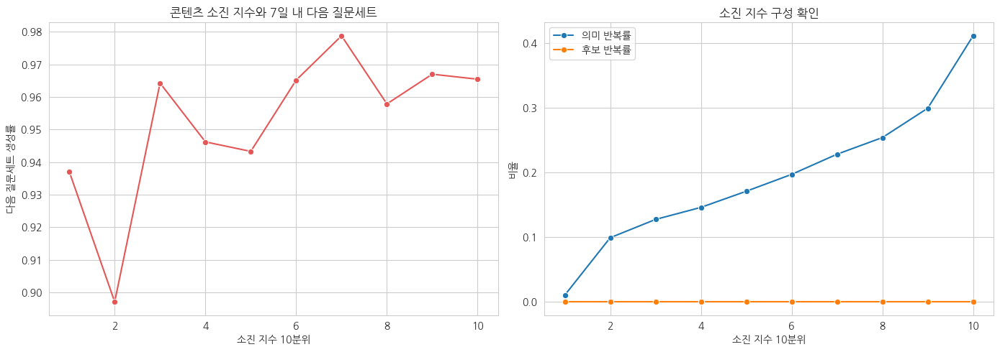

In [ ]:
# 질문세트 소진·다양성 · 다음 질문 이용
piece_follow = piece.copy()
novelty_map = unique_text.set_index('question_text_normalized')['semantic_novelty_to_prior']
piece_follow['semantic_novelty'] = piece_follow.question_text_normalized.map(novelty_map)
qset_follow = piece_follow.dropna(subset=['question_set_id']).groupby(['owner_user_id', 'school_id', 'question_set_id'], as_index=False).agg(qset_at=('piece_created_at', 'min'), pieces=('question_piece_id', 'size'), vote_rate=('vote_record_exists', 'mean'), semantic_repeat_rate=('repeat_semantic_090', 'mean'), exact_repeat_rate=('repeat_exact_text', 'mean'), unique_themes=('theme_id', 'nunique'), unique_semantic_groups=('semantic_group_090', 'nunique'), mean_semantic_novelty=('semantic_novelty', 'mean'))
qset_follow['theme_diversity'] = qset_follow.unique_themes / qset_follow.pieces
qset_follow['semantic_diversity'] = qset_follow.unique_semantic_groups / qset_follow.pieces
qset_follow['question_set_id'] = qset_follow.question_set_id.astype(str)
candidate_qset_long = con.execute("\nWITH x AS (\n  SELECT CAST(question_set_id AS VARCHAR) question_set_id,\n         CAST(candidate_user_id AS VARCHAR) candidate_user_id,\n         CAST(candidate_pair_occurrence_number AS DOUBLE) pair_occurrence,\n         CASE WHEN self_candidate_flag=1 THEN 'self'\n              WHEN current_friend_mutual_flag=1 THEN 'mutual_friend'\n              WHEN current_friend_any_direction_flag=1 THEN 'oneway_friend'\n              WHEN same_school_grade_class_current_flag=1 THEN 'same_class'\n              WHEN same_school_grade_current_flag=1 THEN 'same_grade'\n              WHEN same_school_current_flag=1 THEN 'same_school'\n              ELSE 'unknown' END relation_group\n  FROM candidate\n  WHERE analysis_eligible_candidate_canonical_flag=1 AND question_set_id IS NOT NULL\n)\nSELECT question_set_id, relation_group, COUNT(*) candidate_rows,\n       COUNT(DISTINCT candidate_user_id) distinct_candidates,\n       AVG(CAST(pair_occurrence>1 AS DOUBLE)) repeated_candidate_share\nFROM x GROUP BY 1,2\n").df()
rel_counts = candidate_qset_long.pivot(index='question_set_id', columns='relation_group', values='candidate_rows').fillna(0)
candidate_qset = candidate_qset_long.groupby('question_set_id', as_index=False).agg(candidate_rows=('candidate_rows', 'sum'), distinct_candidates=('distinct_candidates', 'sum'), repeated_candidate_share=('repeated_candidate_share', lambda s: np.average(s, weights=candidate_qset_long.loc[s.index, 'candidate_rows'])), relation_types=('relation_group', 'nunique'))
candidate_qset['candidate_unique_ratio'] = candidate_qset.distinct_candidates / candidate_qset.candidate_rows
candidate_qset['candidate_relation_entropy'] = rel_counts.apply(entropy_from_counts, axis=1).reindex(candidate_qset.question_set_id).values
qset_follow = qset_follow.merge(candidate_qset, on='question_set_id', how='left')
qset_follow = qset_follow.sort_values(['owner_user_id', 'qset_at', 'question_set_id']).reset_index(drop=True)
qset_follow['next_qset_at'] = qset_follow.groupby('owner_user_id').qset_at.shift(-1)
observation_end = qset_follow.qset_at.max()
for hours, label in [(24, '24h'), (72, '72h'), (168, '7d')]:
    eligible = qset_follow.qset_at <= observation_end - pd.Timedelta(hours=hours)
    event = qset_follow.next_qset_at.le(qset_follow.qset_at + pd.Timedelta(hours=hours))
    qset_follow[f'next_qset_{label}'] = np.where(eligible, event.astype(float), np.nan)
components = pd.DataFrame(index=qset_follow.index)
components['repeat'] = qset_follow.semantic_repeat_rate.rank(pct=True)
components['low_theme_diversity'] = (-qset_follow.theme_diversity).rank(pct=True)
components['low_semantic_diversity'] = (-qset_follow.semantic_diversity).rank(pct=True)
components['candidate_repeat'] = qset_follow.repeated_candidate_share.rank(pct=True)
components['low_candidate_diversity'] = (-qset_follow.candidate_unique_ratio).rank(pct=True)
qset_follow['content_exhaustion_index'] = components.mean(axis=1, skipna=True)
qset_follow['exhaustion_decile'] = pd.qcut(qset_follow.content_exhaustion_index, 10, labels=False, duplicates='drop') + 1
qset_follow['month'] = qset_follow.qset_at.dt.to_period('M').astype(str)
exhaustion_summary = qset_follow.groupby('exhaustion_decile', as_index=False).agg(qsets=('question_set_id', 'size'), users=('owner_user_id', 'nunique'), exhaustion_index=('content_exhaustion_index', 'mean'), repeat_rate=('semantic_repeat_rate', 'mean'), theme_diversity=('theme_diversity', 'mean'), semantic_diversity=('semantic_diversity', 'mean'), candidate_unique_ratio=('candidate_unique_ratio', 'mean'), candidate_repeat_share=('repeated_candidate_share', 'mean'), next_24h=('next_qset_24h', 'mean'), next_72h=('next_qset_72h', 'mean'), next_7d=('next_qset_7d', 'mean'))
show_save(exhaustion_summary, '01_content_exhaustion_and_next_action')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=exhaustion_summary, x='exhaustion_decile', y='next_7d', marker='o', ax=ax[0], color='#E45756')
ax[0].set(title='콘텐츠 소진 지수와 7일 내 다음 질문세트', xlabel='소진 지수 10분위', ylabel='다음 질문세트 생성률')
sns.lineplot(data=exhaustion_summary, x='exhaustion_decile', y='repeat_rate', marker='o', label='의미 반복률', ax=ax[1])
sns.lineplot(data=exhaustion_summary, x='exhaustion_decile', y='candidate_repeat_share', marker='o', label='후보 반복률', ax=ax[1])
ax[1].set(title='소진 지수 구성 확인', xlabel='소진 지수 10분위', ylabel='비율')
plt.tight_layout()
plt.show()
plt.close('all')


- 소진지수가 높아져도 다음 질문세트 생성률이 계속 낮아지지는 않았다.
- 반복률과 다양성을 하나로 묶은 값만으로 후속 이용 감소를 설명하기는 어려웠다.


,resolution,themes,silhouette_cosine,modularity,mean_seed_ari
0,0.4,8,0.012701,0.550798,0.562442
1,0.6,13,0.037224,0.603540,0.518176
2,0.8,17,0.040506,0.614043,0.596865
3,1.0,20,0.042204,0.616021,0.572764
4,1.2,25,0.038033,0.614496,0.643572


,method,resolution,themes,new_silhouette_cosine,new_seed_ari,old_kmeans_silhouette_pca,old_kmeans_seed_ari,decision
0,Louvain semantic kNN,1.2,25,0.038033,0.643572,0.049407,0.387146,기존보다 안정적인 탐색용 테마로 채택


,refined_theme_id,unique_texts,piece_count,top_terms,representative_questions,theme_label_ko,label_source
9,9,406,172576,사람 / 가장 / 이 / 같 / 것 / 예쁘 / 매력 / 귀엽 / 있 / 어울리 /...,가장 매력적인 사람은? | 묘하게 끌리는 사람은? | 츤데레 매력이 있는 사람은? ...,매력·외모,대표 형태소·대표 질문의 분석자 검토 라벨
14,14,426,127071,친구 / 가장 / 같 / 것 / 하 / 있 / 이 / 잘 / 제일 / 나 / 많 / 말,가장 쩝쩝박사일 것 같은 친구는? | 사랑스러운 친구는? | 친화력이 제일 좋을 것...,친구 성격·친화력,대표 형태소·대표 질문의 분석자 검토 라벨
6,6,249,103607,사람 / 가장 / 같 / 것 / 이 / 잘 / 하 / 되 / 제일 / 크 / 꿈 / 좋,무엇이든 잘 할 것 같은 사람은? | 제일 듬직한 사람은? | 가장 건치인 사람은?...,능력·성숙·신뢰,대표 형태소·대표 질문의 분석자 검토 라벨
13,13,299,84094,사람 / 같 / 것 / 좋아하 / 가장 / 나 / 연애 / 하 / 싶 / 잘 / 애...,펩시 좋아할 것 같은 사람? | 가장 연애 하고 싶어 보이는 사람은? | 좋아하는 ...,연애·호감,대표 형태소·대표 질문의 분석자 검토 라벨
17,17,205,69308,먹 / 같 / 것 / 사람 / 싶 / 카페 / 가 / 친구 / 잘 / 주 / 같이 / 밥,음식취향이 가장 잘 맞을 것 같은 사람은? | 같이 밥먹고 싶은 사람은? | 같이 ...,음식·식사,대표 형태소·대표 질문의 분석자 검토 라벨
4,4,252,68171,사람 / 같 / 것 / 전화 / 가장 / 먼저 / 주 / 연락 / 친구 / 싶 / ...,연락해보고 싶은 사람은? | 뭐만하면 전화 걸 것 같은 친구는? | 전화번호 주고 ...,연락·전화,대표 형태소·대표 질문의 분석자 검토 라벨
10,10,124,64858,사람 / 주 / 싶 / 나 / 가장 / 웃 / 있 / 웃음 / 하 / 것 / 웃기 / 같,제일 유쾌한 사람은? | 기대고 싶은 사람은? | 나를 잘 챙겨주는 사람은? | 챙...,배려·유쾌함,대표 형태소·대표 질문의 분석자 검토 라벨
5,5,197,63447,같이 / 싶 / 가 / 사람 / 친구 / 보 / 놀 / 하 / 같 / 것 / 여행 / 타,같이 놀아보고 싶은 친구는? | 둘이 같이 놀고 싶은 친구는? | 해외여행을 같이 ...,함께 놀기·여행,대표 형태소·대표 질문의 분석자 검토 라벨
12,12,195,57193,것 / 같 / 사람 / 잘 / 하 / 게임 / 가장 / 제일 / 체육 / 운동 / ...,장난치면 제일 잘받아줄 것 같은 사람은? | 게임을 제일 잘할 것 같은 사람은? |...,게임·운동·장난,대표 형태소·대표 질문의 분석자 검토 라벨
0,0,172,54288,학교 / 같 / 것 / 사람 / 공부 / 하 / 가장 / 친구 / 시험 / 가 / ...,가장 공부 잘할 것 같은 친구 한명을 고르면? | 학교 대표 얼굴일 것 같은 사람은...,학교·공부,대표 형태소·대표 질문의 분석자 검토 라벨


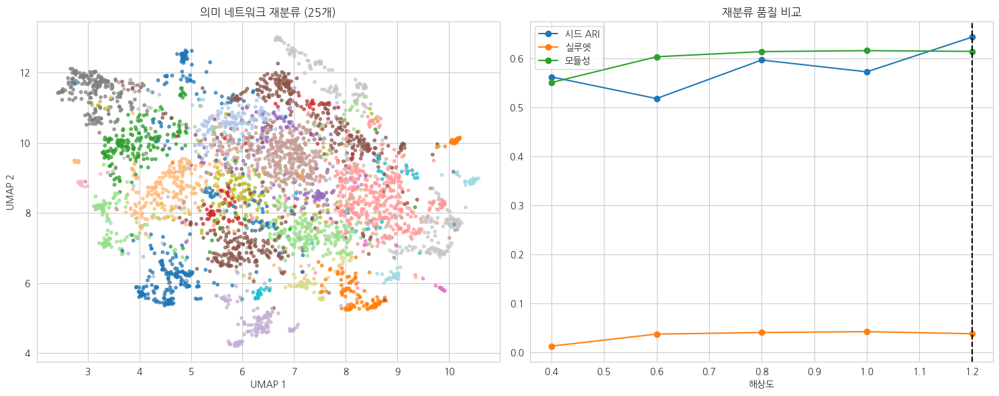

In [ ]:
# 의미 이웃 네트워크 · 테마 재분류
nbr = NearestNeighbors(n_neighbors=13, metric='cosine', n_jobs=-1).fit(embeddings)
knn_dist, knn_idx = nbr.kneighbors(embeddings)
G = nx.Graph()
G.add_nodes_from(range(len(unique_text)))
for i in range(len(unique_text)):
    for d, j in zip(knn_dist[i, 1:], knn_idx[i, 1:]):
        similarity = 1 - float(d)
        if G.has_edge(i, int(j)):
            G[i][int(j)]['weight'] = max(G[i][int(j)]['weight'], similarity)
        else:
            G.add_edge(i, int(j), weight=max(similarity, 0.001))

def communities_to_labels(comms, n):
    labels = np.full(n, -1, dtype=int)
    for k, nodes in enumerate(sorted(comms, key=lambda x: min(x))):
        labels[list(nodes)] = k
    return labels
theme_grid = []
label_store = {}
for resolution in [0.4, 0.6, 0.8, 1.0, 1.2]:
    seed_runs = {}
    for seed in [7, 19, 42, 73]:
        comms = nx.community.louvain_communities(G, weight='weight', resolution=resolution, seed=seed)
        seed_runs[seed] = communities_to_labels(comms, len(unique_text))
    aris = []
    for a_i, a in enumerate(seed_runs):
        for b in list(seed_runs)[a_i + 1:]:
            aris.append(adjusted_rand_score(seed_runs[a], seed_runs[b]))
    labels = seed_runs[42]
    n_themes = len(np.unique(labels))
    sil = silhouette_score(embeddings, labels, metric='cosine', sample_size=min(3000, len(labels)), random_state=42) if 1 < n_themes < len(labels) else np.nan
    mod = nx.community.modularity(G, [set(np.where(labels == k)[0]) for k in np.unique(labels)], weight='weight')
    theme_grid.append({'resolution': resolution, 'themes': n_themes, 'silhouette_cosine': sil, 'modularity': mod, 'mean_seed_ari': np.mean(aris)})
    label_store[resolution] = labels
theme_grid = pd.DataFrame(theme_grid)
valid = theme_grid.query('themes>=6 and themes<=30').copy()
if valid.empty:
    valid = theme_grid.copy()
valid['selection_score'] = valid.silhouette_cosine + 0.1 * valid.modularity + 0.1 * valid.mean_seed_ari
best_resolution = float(valid.loc[valid.selection_score.idxmax(), 'resolution'])
refined_labels = label_store[best_resolution]
unique_text['refined_theme_id'] = refined_labels
refined_rows = []
for t in sorted(np.unique(refined_labels)):
    idx = np.where(refined_labels == t)[0]
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).ravel()
    top_terms = terms[mean_tfidf.argsort()[-12:][::-1]].tolist()
    sub_degree = np.array([G.degree(int(i), weight='weight') for i in idx])
    reps = unique_text.question_text.iloc[idx[np.argsort(-sub_degree)[:4]]].tolist()
    refined_rows.append({'refined_theme_id': int(t), 'unique_texts': len(idx), 'piece_count': int(unique_text.piece_count.iloc[idx].sum()), 'top_terms': ' / '.join(top_terms), 'representative_questions': ' | '.join(reps)})
refined_theme_summary = pd.DataFrame(refined_rows).sort_values('piece_count', ascending=False)
theme_label_ko = {0: '학교·공부', 1: '생일·선물', 2: '친해지고 싶은 관계', 3: 'SNS·연예인 이미지', 4: '연락·전화', 5: '함께 놀기·여행', 6: '능력·성숙·신뢰', 7: '집·잠·생활습관', 8: '인생·극한상황', 9: '매력·외모', 10: '배려·유쾌함', 11: '음악·춤', 12: '게임·운동·장난', 13: '연애·호감', 14: '친구 성격·친화력', 15: 'MBTI·유형', 16: '버스·이동 상황', 17: '음식·식사', 18: '패션·헤어', 19: '결혼·가족·미래', 20: '두려움·부정 성향', 21: '글쓰기·목소리·표현', 22: '향기·위생', 23: '사진·셀카', 24: '겨울·눈·온기'}
refined_theme_summary['theme_label_ko'] = refined_theme_summary.refined_theme_id.map(theme_label_ko).fillna('검토 필요')
refined_theme_summary['label_source'] = '대표 형태소·대표 질문의 분석자 검토 라벨'
old_stability = float(theme_stability.adjusted_rand_index.mean())
new_stability = float(theme_grid.loc[theme_grid.resolution.eq(best_resolution), 'mean_seed_ari'].iloc[0])
old_silhouette = float(k_scores.loc[k_scores.k.eq(best_k), 'silhouette'].iloc[0])
new_silhouette = float(theme_grid.loc[theme_grid.resolution.eq(best_resolution), 'silhouette_cosine'].iloc[0])
theme_decision = pd.DataFrame([{'method': 'Louvain semantic kNN', 'resolution': best_resolution, 'themes': int(len(np.unique(refined_labels))), 'new_silhouette_cosine': new_silhouette, 'new_seed_ari': new_stability, 'old_kmeans_silhouette_pca': old_silhouette, 'old_kmeans_seed_ari': old_stability, 'decision': '기존보다 안정적인 탐색용 테마로 채택' if 6 <= len(np.unique(refined_labels)) <= 30 and new_stability >= old_stability + 0.1 and (new_silhouette >= 0) else '품질 부족: 기존 탐색 테마 유지'}])
show_save(theme_grid, '02_refined_theme_model_selection')
show_save(theme_decision, '02b_refined_theme_decision')
show_save(refined_theme_summary, '02c_refined_theme_summary')
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sc = ax[0].scatter(unique_text.umap_x, unique_text.umap_y, c=refined_labels, cmap='tab20', s=10, alpha=0.7)
ax[0].set(title=f'의미 네트워크 재분류 ({len(np.unique(refined_labels))}개)', xlabel='UMAP 1', ylabel='UMAP 2')
ax[1].plot(theme_grid.resolution, theme_grid.mean_seed_ari, marker='o', label='시드 ARI')
ax[1].plot(theme_grid.resolution, theme_grid.silhouette_cosine, marker='o', label='실루엣')
ax[1].plot(theme_grid.resolution, theme_grid.modularity, marker='o', label='모듈성')
ax[1].axvline(best_resolution, color='black', ls='--')
ax[1].set(title='재분류 품질 비교', xlabel='해상도')
ax[1].legend()
plt.tight_layout()
plt.show()
if 6 <= len(np.unique(refined_labels)) <= 30 and new_stability >= old_stability + 0.1 and (new_silhouette >= 0):
    refined_map = unique_text.set_index('question_text_normalized').refined_theme_id
    piece_follow['analysis_theme_id'] = piece_follow.question_text_normalized.map(refined_map)
else:
    piece_follow['analysis_theme_id'] = piece_follow.theme_id
plt.close('all')


- Louvain 25개 테마의 평균 ARI는 0.644로 K-means의 0.387보다 높다.
- 탐색용 분류의 안정성은 나아졌지만 군집 간 경계는 약하다. 한국어 테마명은 대표 질문을 검토해 붙인 라벨이다.


,users,repeat_event_users,logrank_stat,logrank_p,caution
0,4972,4462,1225.253068,0.0,이용량 사후 구간 비교는 기술 통계


,usage_quartile,day,repeat_free_survival,users
0,Q1 낮음,0,0.995977,1243
1,Q1 낮음,1,0.650928,1243
2,Q1 낮음,3,0.423437,1243
3,Q1 낮음,7,0.276697,1243
4,Q1 낮음,14,0.208618,1243
5,Q1 낮음,30,0.169244,1243
6,Q1 낮음,60,0.149641,1243
7,Q1 낮음,90,0.137171,1243
8,Q2,0,0.997586,1243
9,Q2,1,0.322607,1243


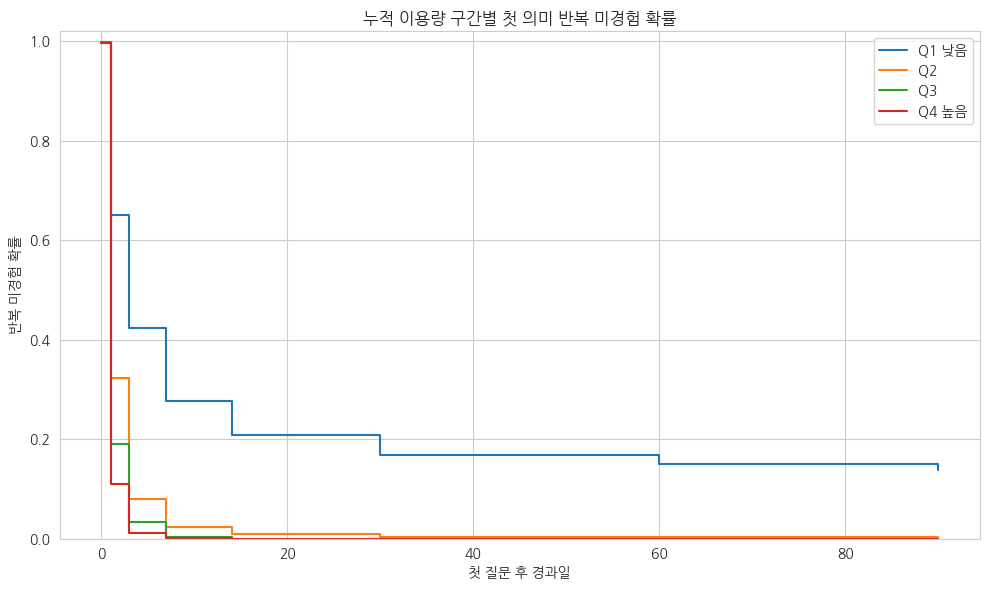

In [ ]:
# 첫 의미 반복까지의 시간 · 이용량별 비교
user_survival = []
for uid, g in piece_follow.sort_values('piece_created_at').groupby('owner_user_id'):
    start = g.piece_created_at.min()
    end = g.piece_created_at.max()
    hit = g.loc[g.repeat_semantic_090.eq(1), 'piece_created_at']
    event = int(len(hit) > 0)
    stop = hit.min() if event else end
    user_survival.append({'owner_user_id': uid, 'school_id': g.school_id.iloc[0], 'signup_month': pd.to_datetime(g.signup_at.iloc[0]).to_period('M').strftime('%Y-%m') if pd.notna(g.signup_at.iloc[0]) else 'missing', 'lifetime_pieces': len(g), 'duration_days': max((stop - start).total_seconds() / 86400, 0), 'repeat_event': event})
user_survival = pd.DataFrame(user_survival)
user_survival['usage_quartile'] = pd.qcut(user_survival.lifetime_pieces.rank(method='first'), 4, labels=['Q1 낮음', 'Q2', 'Q3', 'Q4 높음'])

def km_points(df, times=(0, 1, 3, 7, 14, 30, 60, 90)):
    rows = []
    for group, g in df.groupby('usage_quartile', observed=True):
        for t in times:
            event_times = np.sort(g.loc[g.repeat_event.eq(1), 'duration_days'].unique())
            surv = 1.0
            for et in event_times[event_times <= t]:
                risk = (g.duration_days >= et).sum()
                d = (g.duration_days.eq(et) & g.repeat_event.eq(1)).sum()
                if risk > 0:
                    surv *= 1 - d / risk
            rows.append({'usage_quartile': group, 'day': t, 'repeat_free_survival': surv, 'users': len(g)})
    return pd.DataFrame(rows)
km_table = km_points(user_survival)
try:
    lr_stat, lr_p = survdiff(user_survival.duration_days, user_survival.repeat_event, user_survival.usage_quartile.cat.codes)
except Exception:
    lr_stat, lr_p = (np.nan, np.nan)
survival_test = pd.DataFrame([{'users': len(user_survival), 'repeat_event_users': int(user_survival.repeat_event.sum()), 'logrank_stat': lr_stat, 'logrank_p': lr_p, 'caution': '이용량 사후 구간 비교는 기술 통계'}])
show_save(survival_test, '03_first_repeat_survival_test')
show_save(km_table, '03b_first_repeat_km_points')
fig, ax = plt.subplots(figsize=(10, 6))
for name, g in km_table.groupby('usage_quartile', observed=True):
    ax.step(g.day, g.repeat_free_survival, where='post', label=name)
ax.set(title='누적 이용량 구간별 첫 의미 반복 미경험 확률', xlabel='첫 질문 후 경과일', ylabel='반복 미경험 확률', ylim=(0, 1.02))
ax.legend()
plt.tight_layout()
plt.show()
plt.close('all')


- 4,972명 중 4,462명에게 의미가 같은 질문이 다시 생성됐다. 이용량이 많은 그룹일수록 첫 반복 시점도 빨랐다.
- 그룹은 전체 관찰기간의 이용량으로 나눈 것이므로, 반복을 빨리 만난 이후의 이용량도 분류에 포함돼 있다.


/usr/local/lib/python3.13/dist-packages/statsmodels/formula/formulatools.py:70: FutureWarning: EvalEnvironment is deprecated and support be removed in a future version. You can
pass variables using a dict[str, value] where str is the variable name and the
value is the array of values.

  result = mgr.get_matrices(


,feature,effect_level,coef,odds_ratio,ci_low,ci_high,p_value,rows,users
0,within_semantic_repeat_rate,사용자 내부,0.114692,1.121528,1.077488,1.167368,2.006471e-08,156533,4972
1,within_theme_diversity,사용자 내부,0.604604,1.830528,1.767917,1.895357,4.159852e-254,156533,4972
2,within_candidate_relation_entropy,사용자 내부,0.829924,2.293145,2.102174,2.501465,4.338759e-78,156533,4972
3,within_candidate_unique_ratio,사용자 내부,-1.055948,0.347863,0.331272,0.365283,0.000000e+00,156533,4972
4,between_semantic_repeat_rate,사용자 간,1.730630,5.644211,5.146345,6.190242,2.250178e-295,156533,4972
5,between_theme_diversity,사용자 간,0.730571,2.076267,1.928032,2.235898,2.935955e-83,156533,4972
6,between_candidate_relation_entropy,사용자 간,0.464181,1.590711,1.458906,1.734424,7.112327e-26,156533,4972
7,between_candidate_unique_ratio,사용자 간,-0.189410,0.827447,0.779845,0.877954,3.711958e-10,156533,4972


/usr/local/lib/python3.13/dist-packages/statsmodels/formula/formulatools.py:70: FutureWarning: EvalEnvironment is deprecated and support be removed in a future version. You can
pass variables using a dict[str, value] where str is the variable name and the
value is the array of values.

  result = mgr.get_matrices(


,feature,coef,odds_ratio,ci_low,ci_high,p_value,school_effect,user_se
0,z_semantic_repeat_rate,0.503694,1.654823,1.592917,1.719135,8.033394e-148,fixed (10 schools),cluster robust
1,z_theme_diversity,0.500383,1.649353,1.588059,1.713012,7.216745e-148,fixed (10 schools),cluster robust
2,z_candidate_relation_entropy,0.691072,1.995854,1.835875,2.169774,4.190514e-59,fixed (10 schools),cluster robust
3,z_candidate_unique_ratio,-0.500355,0.606315,0.580510,0.633267,1.399588e-112,fixed (10 schools),cluster robust


/usr/local/lib/python3.13/dist-packages/statsmodels/formula/formulatools.py:70: FutureWarning: EvalEnvironment is deprecated and support be removed in a future version. You can
pass variables using a dict[str, value] where str is the variable name and the
value is the array of values.

  result = mgr.get_matrices(


,feature,odds_ratio,ci_low,ci_high,p_value,controls,user_se
0,content_exhaustion_index,1.089776,1.052655,1.128207,0.000001,school + month,cluster robust


,dose_decile,repeat_dose,qsets,next_7d,window_qsets
0,1,0.002827,14205,0.962760,10
1,2,0.032058,14204,0.955646,10
2,3,0.060636,14204,0.950014,10
3,4,0.093271,14204,0.942763,10
4,5,0.131317,14204,0.937905,10
5,6,0.174413,14204,0.937764,10
6,7,0.223589,14204,0.944523,10
7,8,0.280483,14204,0.950084,10
8,9,0.358249,14204,0.958181,10
9,10,0.523482,14205,0.964449,10


,cosine_threshold,rows,similar_share,vote_rate_novel,vote_rate_similar,difference
0,0.70,1263678,0.428541,0.968509,0.953564,-0.014945
1,0.75,1263678,0.283442,0.966178,0.951806,-0.014372
2,0.80,1263678,0.169670,0.964418,0.950781,-0.013637
3,0.85,1263678,0.088022,0.963577,0.946849,-0.016727
4,0.90,1263678,0.040398,0.962707,0.947777,-0.014931
5,0.95,1263678,0.011091,0.962306,0.944131,-0.018175


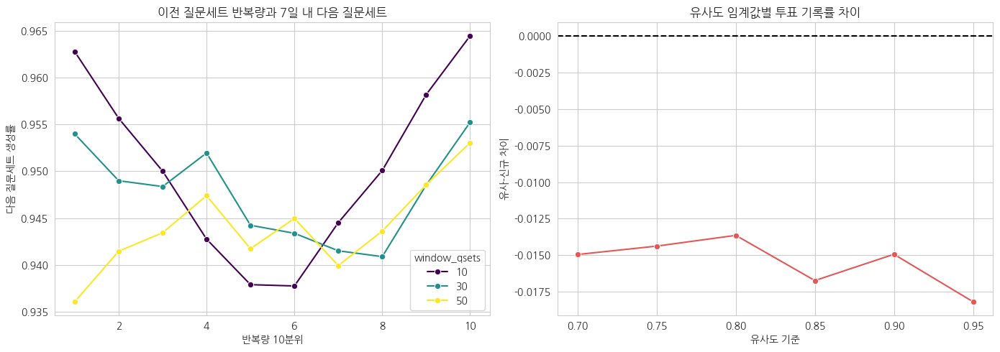

In [ ]:
# 사용자 내부 변화 · 반복 용량 · 신규성 민감도
model_q = qset_follow.dropna(subset=['next_qset_7d', 'content_exhaustion_index']).copy()
fe_features = ['semantic_repeat_rate', 'theme_diversity', 'candidate_relation_entropy', 'candidate_unique_ratio']
for c in fe_features:
    model_q['z_' + c] = zscore(model_q[c].fillna(model_q[c].median()))
within_terms = []
between_terms = []
for c in fe_features:
    base = 'z_' + c
    user_mean = model_q.groupby('owner_user_id')[base].transform('mean')
    model_q['within_' + c] = model_q[base] - user_mean
    model_q['between_' + c] = user_mean
    within_terms.append('within_' + c)
    between_terms.append('between_' + c)
within_formula = 'next_qset_7d ~ ' + ' + '.join(within_terms + between_terms) + ' + C(school_id) + C(month)'
within_fit = smf.glm(within_formula, data=model_q, family=sm.families.Binomial(), eval_env=-1).fit(cov_type='cluster', cov_kwds={'groups': model_q.owner_user_id})
wb_terms = within_terms + between_terms
conditional_result = pd.DataFrame({'feature': wb_terms, 'effect_level': ['사용자 내부'] * len(within_terms) + ['사용자 간'] * len(between_terms), 'coef': [within_fit.params[x] for x in wb_terms], 'odds_ratio': [np.exp(within_fit.params[x]) for x in wb_terms], 'ci_low': [np.exp(within_fit.conf_int().loc[x, 0]) for x in wb_terms], 'ci_high': [np.exp(within_fit.conf_int().loc[x, 1]) for x in wb_terms], 'p_value': [within_fit.pvalues[x] for x in wb_terms], 'rows': len(model_q), 'users': model_q.owner_user_id.nunique()})
show_save(conditional_result, '04_user_within_between_logit')
formula = 'next_qset_7d ~ z_semantic_repeat_rate + z_theme_diversity + z_candidate_relation_entropy + z_candidate_unique_ratio + C(school_id) + C(month)'
glm = smf.glm(formula, data=model_q, family=sm.families.Binomial(), eval_env=-1).fit(cov_type='cluster', cov_kwds={'groups': model_q.owner_user_id})
main_terms = ['z_semantic_repeat_rate', 'z_theme_diversity', 'z_candidate_relation_entropy', 'z_candidate_unique_ratio']
cluster_result = pd.DataFrame({'feature': main_terms, 'coef': [glm.params[x] for x in main_terms], 'odds_ratio': [np.exp(glm.params[x]) for x in main_terms], 'ci_low': [np.exp(glm.conf_int().loc[x, 0]) for x in main_terms], 'ci_high': [np.exp(glm.conf_int().loc[x, 1]) for x in main_terms], 'p_value': [glm.pvalues[x] for x in main_terms], 'school_effect': 'fixed (10 schools)', 'user_se': 'cluster robust'})
show_save(cluster_result, '05_school_fixed_user_cluster_model')
model_q['z_content_exhaustion_index'] = zscore(model_q.content_exhaustion_index)
composite_fit = smf.glm('next_qset_7d ~ z_content_exhaustion_index + C(school_id) + C(month)', data=model_q, family=sm.families.Binomial(), eval_env=-1).fit(cov_type='cluster', cov_kwds={'groups': model_q.owner_user_id})
composite_result = pd.DataFrame([{'feature': 'content_exhaustion_index', 'odds_ratio': np.exp(composite_fit.params['z_content_exhaustion_index']), 'ci_low': np.exp(composite_fit.conf_int().loc['z_content_exhaustion_index', 0]), 'ci_high': np.exp(composite_fit.conf_int().loc['z_content_exhaustion_index', 1]), 'p_value': composite_fit.pvalues['z_content_exhaustion_index'], 'controls': 'school + month', 'user_se': 'cluster robust'}])
show_save(composite_result, '05b_exhaustion_composite_model')
for window in [10, 30, 50]:
    qset_follow[f'prior_{window}_qset_repeat_rate'] = qset_follow.groupby('owner_user_id').semantic_repeat_rate.transform(lambda s: s.shift().rolling(window, min_periods=max(3, window // 5)).mean())
dose_rows = []
for window in [10, 30, 50]:
    col = f'prior_{window}_qset_repeat_rate'
    d = qset_follow.dropna(subset=[col, 'next_qset_7d']).copy()
    d['dose_decile'] = pd.qcut(d[col].rank(method='first'), 10, labels=False) + 1
    a = d.groupby('dose_decile', as_index=False).agg(repeat_dose=(col, 'mean'), qsets=('question_set_id', 'size'), next_7d=('next_qset_7d', 'mean'))
    a['window_qsets'] = window
    dose_rows.append(a)
dose_response = pd.concat(dose_rows, ignore_index=True)
show_save(dose_response, '07_repeat_dose_response')
novelty_threshold = []
for th in np.arange(0.7, 0.951, 0.05):
    similar = piece_follow.max_similarity_to_prior_text.ge(th) if 'max_similarity_to_prior_text' in piece_follow else piece_follow.question_text_normalized.map(unique_text.set_index('question_text_normalized').max_similarity_to_prior_text).ge(th)
    valid = piece_follow.question_text_normalized.map(unique_text.set_index('question_text_normalized').max_similarity_to_prior_text).notna()
    sub = piece_follow.loc[valid].copy()
    group = similar.loc[valid]
    novelty_threshold.append({'cosine_threshold': round(float(th), 2), 'rows': len(sub), 'similar_share': group.mean(), 'vote_rate_novel': sub.loc[~group, 'vote_record_exists'].mean(), 'vote_rate_similar': sub.loc[group, 'vote_record_exists'].mean(), 'difference': sub.loc[group, 'vote_record_exists'].mean() - sub.loc[~group, 'vote_record_exists'].mean()})
novelty_threshold = pd.DataFrame(novelty_threshold)
show_save(novelty_threshold, '08_novelty_threshold_sensitivity')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=dose_response, x='dose_decile', y='next_7d', hue='window_qsets', marker='o', palette='viridis', ax=ax[0])
ax[0].set(title='이전 질문세트 반복량과 7일 내 다음 질문세트', xlabel='반복량 10분위', ylabel='다음 질문세트 생성률')
sns.lineplot(data=novelty_threshold, x='cosine_threshold', y='difference', marker='o', ax=ax[1], color='#E45756')
ax[1].axhline(0, color='black', ls='--')
ax[1].set(title='유사도 임계값별 투표 기록률 차이', xlabel='유사도 기준', ylabel='유사-신규 차이')
plt.tight_layout()
plt.show()
plt.close('all')
team7_content_assets['summary'] = {'exhaustion_or': float(composite_result.odds_ratio.iloc[0]), 'within_theme_or': float(conditional_result.loc[conditional_result.feature.eq('within_theme_diversity'), 'odds_ratio'].iloc[0]), 'within_relation_or': float(conditional_result.loc[conditional_result.feature.eq('within_candidate_relation_entropy'), 'odds_ratio'].iloc[0])}


- 동일 사용자 내 테마 다양성의 오즈비는 1.831, 후보 관계 엔트로피는 2.293이었다. 종합 소진지수의 오즈비는 1.090으로, 후속 이용 감소를 뒷받침하지 않았다.
- 기존 문구와 비슷한 신규 문구의 투표 기록률은 유사도 기준별로 약 1.4~1.8%p 낮았지만, 조건을 맞추지 않은 관측 차이다.


### 3-3-6. 질문 표현·학교 맥락·관계 경험

- 표현 방식과 학교별 공급 범위를 살펴보고, 첫 친구 수락·첫 투표 수신 전후의 질문 이용을 비교했다. 관계가 생긴 시점에는 가입과 학교 내 확산도 함께 일어날 수 있다.


,k,silhouette_cosine,seed_ari,score
0,6,0.039129,0.317209,0.070850
1,8,0.055639,0.713570,0.126996
2,10,0.053951,0.340337,0.087985
3,12,0.007826,0.164127,0.024239
4,14,-0.031677,0.053500,-0.026327
5,16,-0.024830,0.372655,0.012436
6,18,-0.063613,0.316791,-0.031934
7,20,-0.056255,0.659344,0.009680


,template_id,unique_texts,piece_count,top_character_patterns,representative_questions
2,2,1616,714790,은? / 사람은? / 람은? / 사람은? / 사람은? / 람은? / 사람은...,무대체질일 것 같은 사람은? | 첫째일 것 같은 사람은? | 스벅 VIP일 것 같은...
3,3,1111,217487,사람 / 사람 / 같은 / 같은 / 같은 / 것 / 사람 / 친구...,소식좌일 것 같은 사람 | 똘똘할 것 같은 사람 | 외동일 것 같은 사람 | 털털할...
4,4,353,133423,싶은 / 싶은 / 싶은 / 같이 / 같이 / 같이 / 사람 / 하고...,같이 벛꽃 구경하고 싶은 사람은? | 같이 카공하고 싶은 사람은? | 같이 피시방가...
0,0,587,131103,구는? / 친구는? / 구는? / 친구는? / 친구는? / 는? / 친구는 ...,예체능인 친구는? | 보부상 재질인 친구는? | 보디가드 같은 친구는? | 팜므파탈...
5,5,113,34805,많이 / 많이 / 많이 / 같은 / 것 / 가장 / 가장 / 가...,가장 충동구매를 많이 할 것 같은 사람 | 가장 더위를 많이 탈 것 같은 사람은? ...
7,7,79,17836,좋아할 / 좋아할 / 좋아할 / 좋아할 / 아할 / 좋아 / 것 / ...,산리오 좋아할 것 같은 사람은? | 마카롱을 좋아할 것 같은 사람은? | 초밥 좋아...
6,6,37,15668,나중에 / 나중에 / 나중에 / 나중에 / 나중 / 중에 / 될 / ...,나중에 대통령이 될 것 같은 사람 | 나중에 아티스트가 될 것 같은 사람은? | 나...
1,1,2,364,이중에 / 이중에 / 눈에 / 이중에 / 이중에 / 이중 / 계속 /...,이중에 계속 내눈에 보이는 사람 | 이중에 제일 쿨한사람


,question_text,piece_count,weighted_degree,pagerank,nearest_cosine,refined_theme_id,network_role
311,가장 쩝쩝박사일 것 같은 친구는?,18,113.489638,0.001903,0.903885,14,의미 허브
3401,친해지고 싶은 친구는?,356,96.343143,0.001553,0.962091,2,의미 허브
1860,사랑스러운 친구는?,33,68.531140,0.001130,0.903526,14,의미 허브
2392,어산데 친해지고 싶은 친구는?,279,68.814684,0.001119,0.962091,2,의미 허브
1340,말걸고 싶은 친구는?,22,66.417177,0.001118,0.898348,2,의미 허브
3572,펩시 좋아할 것 같은 사람?,378,62.438281,0.001092,0.912741,13,의미 허브
1518,무엇이든 잘 할 것 같은 사람은?,404,51.323119,0.001028,0.790696,6,의미 허브
2962,장난치면 제일 잘받아줄 것 같은 사람은?,41,53.332316,0.001020,0.765120,12,의미 허브
3407,친화력이 제일 좋을 것 같은 친구는?,35,60.766510,0.001007,0.864028,14,의미 허브
171,가장 매력적인 사람은?,1729,57.258133,0.001003,0.953027,9,의미 허브


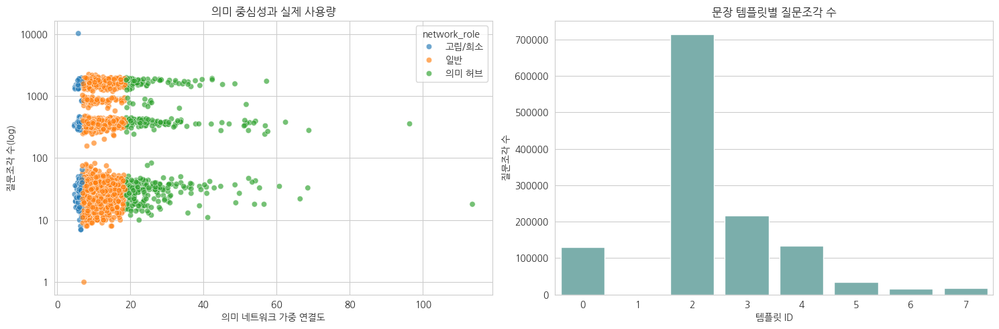

In [ ]:
# 문자 표현 군집 · 의미 네트워크 중심 문구
char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), min_df=3, max_features=6000)
Xchar = char_vec.fit_transform(unique_text.question_text.fillna(''))
template_grid = []
template_models = {}
for k in [6, 8, 10, 12, 14, 16, 18, 20]:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=512, n_init=20)
    lab = km.fit_predict(Xchar)
    sil = silhouette_score(Xchar, lab, metric='cosine', sample_size=min(2500, len(lab)), random_state=42)
    km2 = MiniBatchKMeans(n_clusters=k, random_state=73, batch_size=512, n_init=20)
    lab2 = km2.fit_predict(Xchar)
    template_grid.append({'k': k, 'silhouette_cosine': sil, 'seed_ari': adjusted_rand_score(lab, lab2)})
    template_models[k] = (km, lab)
template_grid = pd.DataFrame(template_grid)
template_grid['score'] = template_grid.silhouette_cosine + 0.1 * template_grid.seed_ari
template_k = int(template_grid.loc[template_grid.score.idxmax(), 'k'])
template_model, template_labels = template_models[template_k]
char_terms = np.array(char_vec.get_feature_names_out())
template_rows = []
for t in range(template_k):
    idx = np.where(template_labels == t)[0]
    center = template_model.cluster_centers_[t]
    reps = unique_text.question_text.iloc[idx[np.argsort(-np.asarray(Xchar[idx].dot(center)).ravel())[:4]]].tolist()
    top = char_terms[center.argsort()[-10:][::-1]].tolist()
    template_rows.append({'template_id': t, 'unique_texts': len(idx), 'piece_count': int(unique_text.piece_count.iloc[idx].sum()), 'top_character_patterns': ' / '.join(top), 'representative_questions': ' | '.join(reps)})
template_summary = pd.DataFrame(template_rows).sort_values('piece_count', ascending=False)
show_save(template_grid, '11_template_cluster_selection')
show_save(template_summary, '11b_template_cluster_summary')
weighted_degree = dict(G.degree(weight='weight'))
pagerank = nx.pagerank(G, weight='weight')
semantic_network = pd.DataFrame({'question_text': unique_text.question_text, 'piece_count': unique_text.piece_count, 'weighted_degree': [weighted_degree.get(i, 0) for i in range(len(unique_text))], 'pagerank': [pagerank.get(i, 0) for i in range(len(unique_text))], 'nearest_cosine': unique_text.nearest_cosine, 'refined_theme_id': refined_labels})
semantic_network['network_role'] = pd.cut(semantic_network.weighted_degree, [-np.inf, semantic_network.weighted_degree.quantile(0.1), semantic_network.weighted_degree.quantile(0.9), np.inf], labels=['고립/희소', '일반', '의미 허브'], include_lowest=True)
show_save(semantic_network.sort_values('pagerank', ascending=False), '12_semantic_network_centrality', head=30)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=semantic_network, x='weighted_degree', y='piece_count', hue='network_role', alpha=0.65, ax=ax[0])
ax[0].set_yscale('log')
team7_plain_log_ticks(ax[0], 'y')
ax[0].set(title='의미 중심성과 실제 사용량', xlabel='의미 네트워크 가중 연결도', ylabel='질문조각 수(log)')
sns.barplot(data=template_summary.head(12), x='template_id', y='piece_count', color='#72B7B2', ax=ax[1])
ax[1].set(title='문장 템플릿별 질문조각 수', xlabel='템플릿 ID', ylabel='질문조각 수')
plt.tight_layout()
plt.show()
plt.close('all')


- 문자 군집에는 ‘사람은?’, ‘친구는?’, ‘같이 하고 싶은’ 같은 문장 틀이 반복된다. ‘사람은?’ 중심 군집에는 1,616개 문구가 묶였다.
- 의미상 대표적인 문구와 많이 공급된 문구는 다를 수 있다.


In [ ]:
# 문구 공급 기간 · 학교 공통성 · 테마 이동
content_life = unique_text[['question_text', 'piece_count', 'first_at', 'last_at', 'theme_id']].copy()
content_life['first_at'] = pd.to_datetime(content_life.first_at)
content_life['last_at'] = pd.to_datetime(content_life.last_at)
content_life['active_days'] = (content_life.last_at - content_life.first_at).dt.total_seconds() / 86400
content_life['first_month'] = content_life.first_at.dt.to_period('M').astype(str)
content_life['life_type'] = pd.cut(content_life.active_days, [-0.001, 1, 7, 30, np.inf], labels=['1일 이내', '2-7일', '8-30일', '31일+'])
life_summary = content_life.groupby(['first_month', 'life_type'], observed=True).agg(texts=('question_text', 'size'), pieces=('piece_count', 'sum'), median_active_days=('active_days', 'median')).reset_index()
show_save(life_summary, '13_content_lifetime_by_cohort')
supplier_audit = pd.DataFrame([{'analysis': '질문 공급자 집중도', 'status': 'NOT_IDENTIFIABLE', 'available_key': '질문 ID·질문세트 소유자', 'missing_key': '질문 마스터 생성자 또는 운영/UGC 구분', 'reason': '질문세트 소유자는 질문을 푼 사용자이지 질문 문구 생성자가 아님'}])
show_save(supplier_audit, '14_question_supplier_identifiability')
school_text = piece_follow.groupby(['question_text_normalized', 'school_id']).size().rename('pieces').reset_index()
text_school = school_text.groupby('question_text_normalized').agg(schools_used=('school_id', 'nunique'), pieces=('pieces', 'sum')).reset_index()
text_school['scope_type'] = np.select([text_school.schools_used.eq(1), text_school.schools_used.le(3), text_school.schools_used.eq(10)], ['학교 고유', '2-3개 학교', '10개 학교 공통'], default='4-9개 학교')
local_summary = text_school.groupby('scope_type', as_index=False).agg(texts=('question_text_normalized', 'size'), pieces=('pieces', 'sum'))
local_summary['text_share'] = local_summary.texts / local_summary.texts.sum()
local_summary['piece_share'] = local_summary.pieces / local_summary.pieces.sum()
show_save(local_summary, '15_school_content_localization')
transition_base = piece_follow.dropna(subset=['question_set_id', 'question_position']).sort_values(['question_set_id', 'question_position']).copy()
transition_base['next_theme'] = transition_base.groupby('question_set_id').analysis_theme_id.shift(-1)
trans = transition_base.dropna(subset=['next_theme']).copy()
trans['next_theme'] = trans.next_theme.astype(int)
transition = trans.groupby(['analysis_theme_id', 'next_theme']).size().rename('transitions').reset_index()
transition['from_total'] = transition.groupby('analysis_theme_id').transitions.transform('sum')
transition['transition_rate'] = transition.transitions / transition.from_total
same_theme_rate = trans.analysis_theme_id.eq(trans.next_theme).mean()
theme_probs = transition_base.analysis_theme_id.value_counts(normalize=True)
random_same_rate = float((theme_probs ** 2).sum())
transition_test = pd.DataFrame([{'transitions': len(trans), 'observed_same_theme_rate': same_theme_rate, 'independent_expected_rate': random_same_rate, 'difference': same_theme_rate - random_same_rate}])
show_save(transition.sort_values(['analysis_theme_id', 'transition_rate'], ascending=[True, False]), '16_theme_transition_matrix', head=40)
show_save(transition_test, '16b_theme_transition_same_theme_test')


,first_month,life_type,texts,pieces,median_active_days
0,2023-04,31일+,227,411392,143.086910
1,2023-05,8-30일,51,20341,17.685266
2,2023-05,31일+,1235,765145,129.696447
3,2023-06,8-30일,146,4396,22.080162
4,2023-06,31일+,2238,64201,109.183218
5,2023-07,1일 이내,1,1,0.000000


,analysis,status,available_key,missing_key,reason
0,질문 공급자 집중도,NOT_IDENTIFIABLE,질문 ID·질문세트 소유자,질문 마스터 생성자 또는 운영/UGC 구분,질문세트 소유자는 질문을 푼 사용자이지 질문 문구 생성자가 아님


,scope_type,texts,pieces,text_share,piece_share
0,10개 학교 공통,2029,1215868,0.520523,9.607989e-01
1,4-9개 학교,1868,49607,0.479220,3.920027e-02
2,학교 고유,1,1,0.000257,7.902165e-07


,analysis_theme_id,next_theme,transitions,from_total,transition_rate
9,0,9,6407,47442,0.135049
14,0,14,4865,47442,0.102546
6,0,6,3908,47442,0.082374
13,0,13,3183,47442,0.067092
17,0,17,2630,47442,0.055436
4,0,4,2546,47442,0.053666
10,0,10,2393,47442,0.050441
5,0,5,2329,47442,0.049092
12,0,12,2170,47442,0.045740
0,0,0,1945,47442,0.040997


,transitions,observed_same_theme_rate,independent_expected_rate,difference
0,1108937,0.063283,0.063147,0.000136


- 10개 학교에 공통으로 나온 문구가 전체 공급의 96.08%였다. 한 학교에서만 관측된 문구는 1개로, 공급 대부분이 학교 공통 콘텐츠였다.
- 세트 소유자 정보는 질문을 푼 사용자 정보다. 문구 작성자나 공급자를 알 수 있는 항목은 없다.


,style,rows_with_style,share,vote_rate_without,vote_rate_with,difference
0,style_superlative,499114,0.394408,0.959287,0.966507,0.007220
1,style_together,84009,0.066385,0.962155,0.961849,-0.000305
2,style_hypothetical,532025,0.420415,0.964933,0.958276,-0.006657
3,style_negative,20852,0.016478,0.962337,0.950029,-0.012308
4,style_appearance,14867,0.011748,0.962206,0.956077,-0.006129
5,style_relationship,247015,0.195195,0.964154,0.953808,-0.010345
6,style_emoji_or_symbol,31218,0.024669,0.962186,0.960087,-0.002099


,pairs_similarity_090,pairs_length_gap_5plus,mean_longer_minus_shorter,median_longer_minus_shorter,ttest_p
0,315,57,-0.015894,-0.014718,0.444338


,repeat_structure,rows,users,vote_rate,median_sequence
0,기존 테마·새 의미,899151,4966,0.956935,159.0
1,동일 의미 반복,257791,4462,0.978533,261.0
2,새 테마,108534,4972,0.966259,18.0


,question_id,question_text,rows,actual_vote_rate,adjusted_residual,schools
4577,624,같이 야구장 가보고싶은 친구,806,0.959057,-0.016853,10
4592,639,vote,580,0.956897,-0.016667,10
4551,598,가장 잘보이고 싶은 사람이 누구야?,635,0.957480,-0.016349,10
4572,619,일어나자마자 보고싶은 사람은?,634,0.960568,-0.015017,10
4569,616,전생에 나와 부부였을 것 같은 사람은?,646,0.959752,-0.013879,10
...,...,...,...,...,...,...
2420,320,함께한 추억이 가장 많은 사람은?,1614,0.988228,0.015985,10
1430,230,같이 스몰토크 하다가 밤을 샐 것 같은 사람은?,1752,0.989726,0.016054,10
2497,327,누가 잡아가도 다 헤쳐나올 수 있을 것 같은 사람은?,1663,0.987974,0.017204,10
4204,488,솔직한 모습이 멋진 사람은?,1511,0.988087,0.017571,10


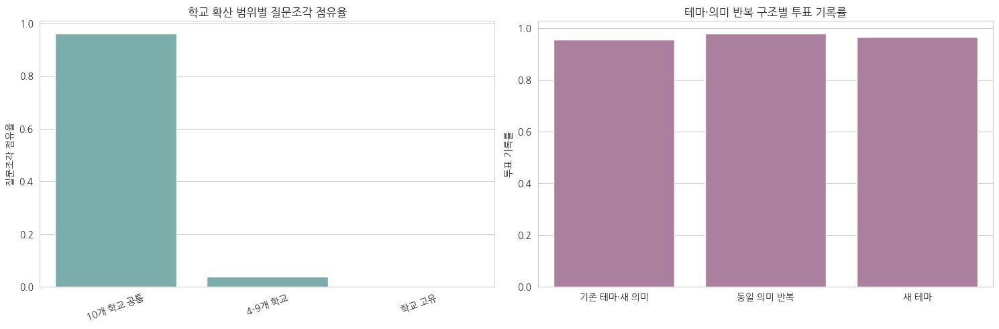

In [ ]:
# 문체 특징 · 유사 문구 길이 · 보정 잔차
text_style = unique_text[['question_text_normalized', 'question_text', 'piece_count']].copy()
raw = text_style.question_text.fillna('').astype(str)
norm = text_style.question_text_normalized.fillna('').astype(str)
text_style['style_superlative'] = norm.str.contains('가장|제일|최고').astype(int)
text_style['style_together'] = norm.str.contains('같이|함께').astype(int)
text_style['style_hypothetical'] = norm.str.contains('것 같|할 것|한다면|라면').astype(int)
text_style['style_negative'] = norm.str.contains('안 |못 |싫|최악|나쁘').astype(int)
text_style['style_appearance'] = norm.str.contains('외모|예쁘|잘생|얼굴|키 |몸매|귀엽').astype(int)
text_style['style_relationship'] = norm.str.contains('친구|연애|사귀|결혼|짝사랑').astype(int)
text_style['style_emoji_or_symbol'] = raw.str.contains('[^0-9A-Za-z가-힣\\s?]').astype(int)
style_map = text_style.set_index('question_text_normalized')
style_cols = [c for c in text_style if c.startswith('style_')]
for c in style_cols:
    piece_follow[c] = piece_follow.question_text_normalized.map(style_map[c]).fillna(0).astype(int)
style_rows = []
for c in style_cols:
    a = piece_follow.groupby(c).vote_record_exists.agg(['size', 'mean']).reset_index()
    style_rows.append({'style': c, 'rows_with_style': int((piece_follow[c] == 1).sum()), 'share': piece_follow[c].mean(), 'vote_rate_without': a.loc[a[c].eq(0), 'mean'].iloc[0] if (a[c] == 0).any() else np.nan, 'vote_rate_with': a.loc[a[c].eq(1), 'mean'].iloc[0] if (a[c] == 1).any() else np.nan})
style_summary = pd.DataFrame(style_rows)
style_summary['difference'] = style_summary.vote_rate_with - style_summary.vote_rate_without
show_save(style_summary, '17_question_style_behavior')
text_perf = piece_follow.groupby('question_text_normalized').agg(vote_rate=('vote_record_exists', 'mean'), rows=('question_piece_id', 'size')).reset_index()
text_perf_map = text_perf.set_index('question_text_normalized')
pair_compare = pair_df.copy()
pair_compare['a_norm'] = pair_compare.question_a.map(normalize_text)
pair_compare['b_norm'] = pair_compare.question_b.map(normalize_text)
pair_compare['a_vote_rate'] = pair_compare.a_norm.map(text_perf_map.vote_rate)
pair_compare['b_vote_rate'] = pair_compare.b_norm.map(text_perf_map.vote_rate)
pair_compare['a_len'] = pair_compare.a_norm.str.len()
pair_compare['b_len'] = pair_compare.b_norm.str.len()
pair_compare = pair_compare.dropna(subset=['a_vote_rate', 'b_vote_rate'])
pair_compare['length_gap'] = (pair_compare.a_len - pair_compare.b_len).abs()
pair_compare['longer_minus_shorter_vote_rate'] = np.where(pair_compare.a_len >= pair_compare.b_len, pair_compare.a_vote_rate - pair_compare.b_vote_rate, pair_compare.b_vote_rate - pair_compare.a_vote_rate)
pair_test = pair_compare.loc[pair_compare.length_gap.ge(5), 'longer_minus_shorter_vote_rate']
similar_pair_test = pd.DataFrame([{'pairs_similarity_090': len(pair_compare), 'pairs_length_gap_5plus': len(pair_test), 'mean_longer_minus_shorter': pair_test.mean(), 'median_longer_minus_shorter': pair_test.median(), 'ttest_p': stats.ttest_1samp(pair_test, 0, nan_policy='omit').pvalue if len(pair_test) > 1 else np.nan}])
show_save(similar_pair_test, '18_similar_pair_expression_test')
piece_follow = piece_follow.sort_values(['owner_user_id', 'piece_created_at', 'question_piece_id']).copy()
piece_follow['theme_occurrence'] = piece_follow.groupby(['owner_user_id', 'analysis_theme_id']).cumcount() + 1
piece_follow['repeat_structure'] = np.select([piece_follow.theme_occurrence.eq(1), piece_follow.theme_occurrence.gt(1) & piece_follow.repeat_semantic_090.eq(0), piece_follow.repeat_semantic_090.eq(1)], ['새 테마', '기존 테마·새 의미', '동일 의미 반복'], default='기타')
repeat_structure = piece_follow.groupby('repeat_structure', as_index=False).agg(rows=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), vote_rate=('vote_record_exists', 'mean'), median_sequence=('user_piece_sequence', 'median'))
show_save(repeat_structure, '19_within_between_theme_repeat')
piece_follow['sequence_band_outlier'] = pd.cut(piece_follow.user_piece_sequence, [0, 10, 50, 100, 200, 500, np.inf], labels=False)
baseline_cols = ['school_id', 'month', 'question_position', 'sequence_band_outlier']
cell_rate = piece_follow.groupby(baseline_cols, dropna=False).vote_record_exists.transform('mean')
piece_follow['vote_residual'] = piece_follow.vote_record_exists - cell_rate
question_outlier = piece_follow.groupby(['question_id', 'question_text'], as_index=False).agg(rows=('question_piece_id', 'size'), actual_vote_rate=('vote_record_exists', 'mean'), adjusted_residual=('vote_residual', 'mean'), schools=('school_id', 'nunique'))
question_outlier = question_outlier[question_outlier.rows >= 500].sort_values('adjusted_residual')
show_save(question_outlier, '20_question_adjusted_outliers')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=local_summary, x='scope_type', y='piece_share', color='#72B7B2', ax=ax[0])
ax[0].set(title='학교 확산 범위별 질문조각 점유율', xlabel='', ylabel='질문조각 점유율')
ax[0].tick_params(axis='x', rotation=20)
sns.barplot(data=repeat_structure, x='repeat_structure', y='vote_rate', color='#B279A2', ax=ax[1])
ax[1].set(title='테마·의미 반복 구조별 투표 기록률', xlabel='', ylabel='투표 기록률')
plt.tight_layout()
plt.show()
plt.close('all')


- 부정 표현이 있는 문구는 없는 문구보다 투표 기록률이 1.23%p, 관계 표현은 1.03%p 낮았다. 표현 외의 조건은 맞추지 않은 비교다.
- 의미가 비슷하고 길이가 다른 57개 문구 쌍에서는 길이에 따른 차이가 뚜렷하지 않았다(p=0.444). 보정 성과가 낮은 문구도 내용을 읽어 볼 검토 대상으로 남겼다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event,metric,paired_users,before_mean,after_mean,after_minus_before,paired_t_p
0,first_friend_accept_at,qsets,3305,1.521936,22.592738,21.070802,0.000000e+00
1,first_friend_accept_at,repeat_rate,3305,0.003823,0.135519,0.131696,0.000000e+00
2,first_friend_accept_at,candidate_diversity,3241,0.546694,0.695181,0.148487,8.903926e-309


,event,metric,paired_users,before_mean,after_mean,after_minus_before,paired_t_p
0,first_received_vote_at,qsets,3787,1.762345,23.214154,21.451809,0.0
1,first_received_vote_at,repeat_rate,3787,0.005941,0.142004,0.136062,0.0
2,first_received_vote_at,candidate_diversity,3739,0.564835,0.703878,0.139043,0.0


,friend_count_band,users,qsets,candidate_unique_ratio,candidate_relation_entropy,repeat_rate,next_7d
0,1-5,15,278,0.165899,0.133329,0.147145,0.928058
1,6-10,41,271,0.292225,0.180208,0.055081,0.797048
2,11-20,226,3571,0.528443,0.190891,0.133944,0.911789
3,21-50,1955,52425,0.652762,0.090997,0.169024,0.944891
4,51+,2735,99994,0.768186,0.068527,0.210230,0.957956


,phase_40,schools,qsets,users,repeat_rate,theme_diversity,candidate_diversity,next_7d
0,40명 이전 14일,1,33,22,0.000000,0.567809,0.487938,1.000000
1,40명 이후 14일,10,126732,4687,0.200291,0.525437,0.717068,0.979595


,analysis,status,assignment_files,required_columns
0,사용자 클러스터별 소진 경로,WAITING_FOR_ASSIGNMENT,,user_id + cluster_label


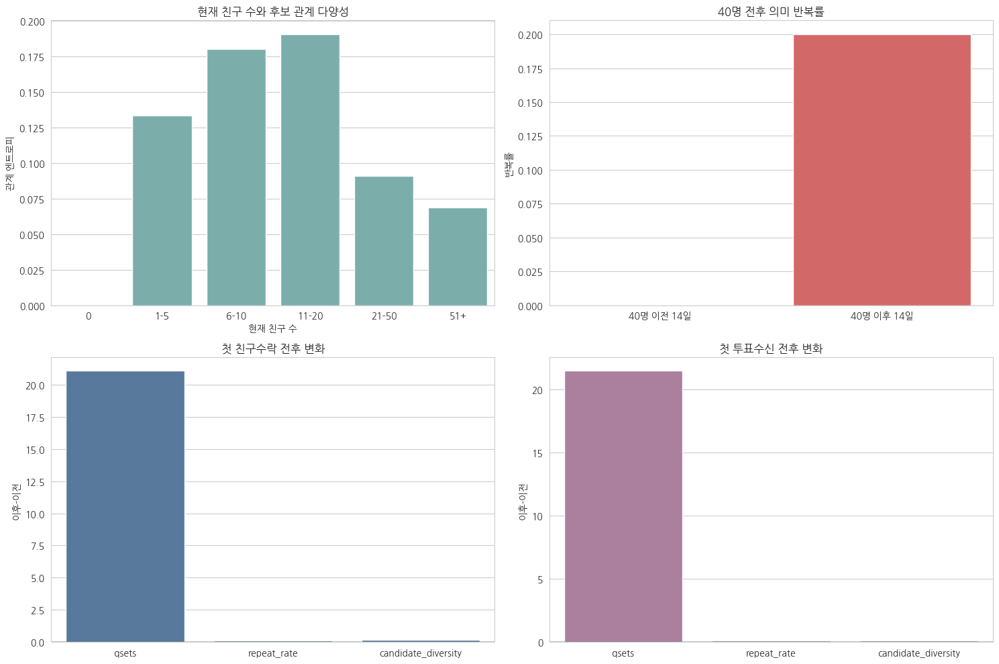

In [ ]:
# 첫 관계 경험 전후 · 친구 규모 · 학교 활성화 연결
qset_event = qset_follow[['owner_user_id', 'school_id', 'question_set_id', 'qset_at', 'semantic_repeat_rate', 'theme_diversity', 'candidate_unique_ratio', 'candidate_relation_entropy', 'next_qset_7d', 'content_exhaustion_index']].copy()
qset_event['owner_user_id'] = qset_event.owner_user_id.astype(str)
qset_event['school_id'] = qset_event.school_id.astype(str)
content_users = pd.DataFrame({'user_id': qset_event.owner_user_id.drop_duplicates().astype(object)})
con.register('content_users_followup', content_users)
friend_file = str(FRIEND_PATH).replace('\\', '/').replace("'", "''")
friend_daily_with_first = con.execute(f"\nWITH endpoints AS (\n  SELECT CAST(send_user_id AS VARCHAR) user_id,\n         TRY_CAST(request_created_at_raw AS TIMESTAMP) created_at,\n         CASE WHEN UPPER(CAST(final_status_label AS VARCHAR)) LIKE '%ACCEPT%'\n              THEN TRY_CAST(request_updated_at_raw AS TIMESTAMP) END accepted_at\n  FROM read_csv_auto('{friend_file}',header=true)\n  WHERE analysis_eligible_request_flag=1 AND CAST(send_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)\n  UNION ALL\n  SELECT CAST(receive_user_id AS VARCHAR), TRY_CAST(request_created_at_raw AS TIMESTAMP),\n         CASE WHEN UPPER(CAST(final_status_label AS VARCHAR)) LIKE '%ACCEPT%'\n              THEN TRY_CAST(request_updated_at_raw AS TIMESTAMP) END\n  FROM read_csv_auto('{friend_file}',header=true)\n  WHERE analysis_eligible_request_flag=1 AND CAST(receive_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)\n), daily AS (\n  SELECT user_id, CAST(created_at AS DATE) event_date, COUNT(*) day_events\n  FROM endpoints WHERE created_at IS NOT NULL GROUP BY 1,2\n), firsts AS (\n  SELECT user_id, MIN(accepted_at) first_friend_accept_at FROM endpoints GROUP BY 1\n)\nSELECT d.*, f.first_friend_accept_at FROM daily d LEFT JOIN firsts f USING(user_id)\n").df()
friend_daily = friend_daily_with_first[['user_id', 'event_date', 'day_events']]
first_accept = friend_daily_with_first.dropna(subset=['first_friend_accept_at']).drop_duplicates('user_id').set_index('user_id').first_friend_accept_at
vote_received_daily = con.execute('\nSELECT CAST(chosen_user_id AS VARCHAR) user_id, CAST(TRY_CAST(vote_record_created_at AS TIMESTAMP) AS DATE) event_date,\n       COUNT(*) day_events\nFROM vote\nWHERE analysis_eligible_vote_record_flag=1 AND CAST(chosen_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)\nGROUP BY 1,2\n').df()
first_received_vote_df = con.execute('\nSELECT CAST(chosen_user_id AS VARCHAR) user_id, MIN(TRY_CAST(vote_record_created_at AS TIMESTAMP)) first_received_vote_at\nFROM vote\nWHERE analysis_eligible_vote_record_flag=1 AND CAST(chosen_user_id AS VARCHAR) IN (SELECT user_id FROM content_users_followup)\nGROUP BY 1\n').df()
first_received_vote = first_received_vote_df.set_index('user_id').first_received_vote_at
user_viral = pd.read_csv(USER_VIRAL_PATH, compression='gzip', usecols=['user_id', 'current_friend_list_length', 'sent_request_count', 'received_request_count', 'analysis_eligible_nonstaff_flag'])
user_viral = user_viral[user_viral.analysis_eligible_nonstaff_flag.eq(1)].copy()
user_viral['user_id'] = user_viral.user_id.astype(str)

def before_after_qsets(first_event, label):
    d = qset_event.merge(first_event.rename(label), left_on='owner_user_id', right_index=True, how='inner')
    d['relative_days'] = (d.qset_at - d[label]).dt.total_seconds() / 86400
    d = d[d.relative_days.between(-7, 7, inclusive='both')]
    d['period'] = np.where(d.relative_days < 0, '이전 7일', '이후 7일')
    agg = d.groupby(['owner_user_id', 'period']).agg(qsets=('question_set_id', 'nunique'), repeat_rate=('semantic_repeat_rate', 'mean'), candidate_diversity=('candidate_unique_ratio', 'mean')).reset_index()
    wide = agg.pivot(index='owner_user_id', columns='period')
    rows = []
    for metric in ['qsets', 'repeat_rate', 'candidate_diversity']:
        if (metric, '이전 7일') in wide and (metric, '이후 7일') in wide:
            x = wide[metric, '이후 7일'] - wide[metric, '이전 7일']
            x = x.dropna()
            rows.append({'event': label, 'metric': metric, 'paired_users': len(x), 'before_mean': wide.loc[x.index, (metric, '이전 7일')].mean(), 'after_mean': wide.loc[x.index, (metric, '이후 7일')].mean(), 'after_minus_before': x.mean(), 'paired_t_p': stats.ttest_1samp(x, 0, nan_policy='omit').pvalue if len(x) > 1 else np.nan})
    return pd.DataFrame(rows)
network_before_after = before_after_qsets(first_accept, 'first_friend_accept_at')
show_save(network_before_after, '21_friend_accept_before_after_content')
value_before_after = before_after_qsets(first_received_vote, 'first_received_vote_at')
show_save(value_before_after, '23_received_vote_before_after_content')
network_content = qset_event.merge(user_viral[['user_id', 'current_friend_list_length']], left_on='owner_user_id', right_on='user_id', how='left')
network_content['friend_count_band'] = pd.cut(network_content.current_friend_list_length, [-1, 0, 5, 10, 20, 50, np.inf], labels=['0', '1-5', '6-10', '11-20', '21-50', '51+'])
network_density_summary = network_content.groupby('friend_count_band', observed=True).agg(users=('owner_user_id', 'nunique'), qsets=('question_set_id', 'size'), candidate_unique_ratio=('candidate_unique_ratio', 'mean'), candidate_relation_entropy=('candidate_relation_entropy', 'mean'), repeat_rate=('semantic_repeat_rate', 'mean'), next_7d=('next_qset_7d', 'mean')).reset_index()
show_save(network_density_summary, '22_current_network_density_candidate_diversity')
school_daily = pd.read_csv(SCHOOL_DAILY_PATH, compression='gzip', usecols=['school_id', 'current_roster_40th_signup_at', 'analysis_eligible_school_day_flag'])
school_daily['school_id'] = school_daily.school_id.astype(str)
school_40 = school_daily[school_daily.analysis_eligible_school_day_flag.eq(1)].dropna(subset=['current_roster_40th_signup_at']).assign(current_roster_40th_signup_at=lambda d: pd.to_datetime(d.current_roster_40th_signup_at, errors='coerce')).groupby('school_id').current_roster_40th_signup_at.min()
growth_content = qset_event.merge(school_40.rename('school_40_at'), left_on='school_id', right_index=True, how='inner')
growth_content['days_from_40'] = (growth_content.qset_at - growth_content.school_40_at).dt.total_seconds() / 86400
growth_content = growth_content[growth_content.days_from_40.between(-14, 14)]
growth_content['phase_40'] = np.where(growth_content.days_from_40 < 0, '40명 이전 14일', '40명 이후 14일')
growth_summary = growth_content.groupby('phase_40', as_index=False).agg(schools=('school_id', 'nunique'), qsets=('question_set_id', 'size'), users=('owner_user_id', 'nunique'), repeat_rate=('semantic_repeat_rate', 'mean'), theme_diversity=('theme_diversity', 'mean'), candidate_diversity=('candidate_unique_ratio', 'mean'), next_7d=('next_qset_7d', 'mean'))
show_save(growth_summary, '24_school_40_before_after_content')
cluster_assignment_candidates = list((ROOT / 'analysis').rglob('*cluster*.csv')) + list((ROOT / 'analysis').rglob('*segment*.csv'))
assignment_found = []
for p in cluster_assignment_candidates:
    try:
        cols = pd.read_csv(p, nrows=2).columns.str.lower().tolist()
        if any((c in cols for c in ['user_id', 'userid', 'member_id'])) and any(('cluster' in c or 'segment' in c for c in cols)):
            assignment_found.append(str(p))
    except Exception:
        pass
cluster_audit = pd.DataFrame([{'analysis': '사용자 클러스터별 소진 경로', 'status': 'READY' if assignment_found else 'WAITING_FOR_ASSIGNMENT', 'assignment_files': ' | '.join(assignment_found), 'required_columns': 'user_id + cluster_label'}])
show_save(cluster_audit, '25_user_cluster_assignment_audit')
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
sns.barplot(data=network_density_summary, x='friend_count_band', y='candidate_relation_entropy', color='#72B7B2', ax=ax[0, 0])
ax[0, 0].set(title='현재 친구 수와 후보 관계 다양성', xlabel='현재 친구 수', ylabel='관계 엔트로피')
if not growth_summary.empty:
    sns.barplot(data=growth_summary, x='phase_40', y='repeat_rate', color='#E45756', ax=ax[0, 1])
    ax[0, 1].set(title='40명 전후 의미 반복률', xlabel='', ylabel='반복률')
if not network_before_after.empty:
    sns.barplot(data=network_before_after, x='metric', y='after_minus_before', color='#4C78A8', ax=ax[1, 0])
    ax[1, 0].axhline(0, color='black', lw=1)
    ax[1, 0].set(title='첫 친구수락 전후 변화', xlabel='', ylabel='이후-이전')
if not value_before_after.empty:
    sns.barplot(data=value_before_after, x='metric', y='after_minus_before', color='#B279A2', ax=ax[1, 1])
    ax[1, 1].axhline(0, color='black', lw=1)
    ax[1, 1].set(title='첫 투표수신 전후 변화', xlabel='', ylabel='이후-이전')
plt.tight_layout()
plt.show()
plt.close('all')


- 첫 친구 수락과 첫 투표 수신 뒤에는 질문 이용과 후보 다양성이 함께 늘었다. 현재 친구 수가 많은 그룹의 후보 다양성도 높았다.
- 학교 활성화 40명 이전 자료는 1개 학교·33개 세트뿐이었다. 활성화 전후 차이를 판단하기에는 이전 표본이 부족했다.


,model,train_rows,test_rows,cutoff,roc_auc,log_loss,auc_gain_vs_content,logloss_change_vs_content
0,content,125226,31307,2023-05-24 08:25:35,0.788485,0.482026,0.000000,0.000000
1,content_network,125226,31307,2023-05-24 08:25:35,0.791584,0.472448,0.003099,-0.009577
2,content_value,125226,31307,2023-05-24 08:25:35,0.785493,0.433867,-0.002992,-0.048158
3,content_network_value,125226,31307,2023-05-24 08:25:35,0.781051,0.436261,-0.007434,-0.045764


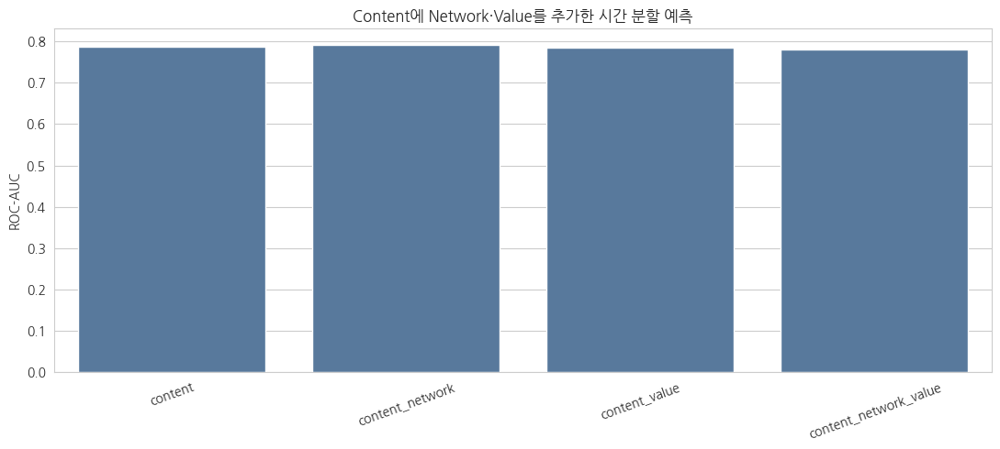

In [ ]:
# 질문세트 이전 관계·수신 이력 · 통합 예측
for _name in ['sim', 'Xchar', 'knn_dist', 'knn_idx', 'transition_base', 'trans', 'school_text']:
    if _name in globals():
        del globals()[_name]
gc.collect()

def prior_event_count(base, daily_input, out_col):
    daily = daily_input[['user_id', 'event_date', 'day_events']].dropna().copy()
    daily['user_id'] = daily.user_id.astype('string')
    daily['event_date'] = pd.to_datetime(daily.event_date)
    daily = daily.sort_values(['user_id', 'event_date'])
    daily[out_col] = daily.groupby('user_id', observed=True, sort=False).day_events.cumsum()
    left = base[['owner_user_id', 'qset_at']].copy()
    left['row_id'] = left.index
    left['event_date'] = left.qset_at.dt.floor('D')
    left['owner_user_id'] = left.owner_user_id.astype('string')
    left = left.sort_values(['event_date', 'owner_user_id'])
    right = daily.rename(columns={'user_id': 'owner_user_id'}).sort_values(['event_date', 'owner_user_id'])
    merged = pd.merge_asof(left, right[['owner_user_id', 'event_date', out_col]], by='owner_user_id', on='event_date', direction='backward', allow_exact_matches=False)
    return merged.set_index('row_id')[out_col].reindex(base.index).fillna(0)
qset_follow['prior_network_events'] = prior_event_count(qset_follow, friend_daily, 'prior_network_events')
qset_follow['prior_received_votes'] = prior_event_count(qset_follow, vote_received_daily, 'prior_received_votes')
integrated = qset_follow.dropna(subset=['next_qset_7d']).sort_values('qset_at').copy()
cut = integrated.qset_at.quantile(0.8)
train_i = integrated[integrated.qset_at < cut]
test_i = integrated[integrated.qset_at >= cut]
specs_integrated = {'content': ['semantic_repeat_rate', 'theme_diversity', 'candidate_relation_entropy', 'candidate_unique_ratio'], 'content_network': ['semantic_repeat_rate', 'theme_diversity', 'candidate_relation_entropy', 'candidate_unique_ratio', 'prior_network_events'], 'content_value': ['semantic_repeat_rate', 'theme_diversity', 'candidate_relation_entropy', 'candidate_unique_ratio', 'prior_received_votes'], 'content_network_value': ['semantic_repeat_rate', 'theme_diversity', 'candidate_relation_entropy', 'candidate_unique_ratio', 'prior_network_events', 'prior_received_votes']}
integrated_rows = []
for name, num in specs_integrated.items():
    pre = ColumnTransformer([('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), num), ('cat', OneHotEncoder(handle_unknown='ignore'), ['school_id', 'month'])])
    clf = Pipeline([('pre', pre), ('model', LogisticRegression(max_iter=400, C=0.5, solver='liblinear'))])
    feats = num + ['school_id', 'month']
    clf.fit(train_i[feats], train_i.next_qset_7d.astype(int))
    pred = clf.predict_proba(test_i[feats])[:, 1]
    integrated_rows.append({'model': name, 'train_rows': len(train_i), 'test_rows': len(test_i), 'cutoff': test_i.qset_at.min(), 'roc_auc': roc_auc_score(test_i.next_qset_7d, pred), 'log_loss': log_loss(test_i.next_qset_7d, pred)})
integrated_perf = pd.DataFrame(integrated_rows)
integrated_perf['auc_gain_vs_content'] = integrated_perf.roc_auc - integrated_perf.loc[0, 'roc_auc']
integrated_perf['logloss_change_vs_content'] = integrated_perf.log_loss - integrated_perf.loc[0, 'log_loss']
show_save(integrated_perf, '26_cross_axis_incremental_prediction')
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=integrated_perf, x='model', y='roc_auc', color='#4C78A8', ax=ax)
ax.set(title='Content에 Network·Value를 추가한 시간 분할 예측', xlabel='', ylabel='ROC-AUC')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')


- 관계 변수를 더한 ROC-AUC는 0.7885에서 0.7916으로 약 0.0031 높아졌다.
- 수신 이력을 추가하면 로그 손실은 줄었지만 ROC-AUC는 낮아졌다. 질문세트 생성 이전에 관측된 정보만 입력했다.


In [ ]:
# 추가 로그 · 무작위 실험 항목 정리
future_design = pd.DataFrame([(27, '실제 콘텐츠 퍼널', 'question_impression, candidate_impression, vote/skip, result_view, next_question, session_end', '단계별 전환율·이탈률'), (28, '정확한 스킵 원인', 'skip_event + reason_code', '사유별 스킵률·다음 행동률'), (29, '질문 당시 관계 스냅샷', 'impression_at + candidate relation snapshot', '관계 유형별 선택·후속 행동'), (30, '후보 추천 효과', '투표 여부와 무관한 전체 후보 노출', '친구 후보 노출의 증분 선택효과'), (31, '결과 확인·사회적 피드백 루프', 'notification_sent/open, result_view, reaction, revisit', '결과 확인 후 재방문 전환'), (32, '세션 체류시간·응답시간', 'impression_at, response_at, result_at, session_end', '질문별 응답시간·빠른 스킵'), (33, '콘텐츠 노출 빈도 제한 실험', 'random_assignment + semantic/pair frequency cap', '다음 방문·세트 완료·반복률'), (34, '신규 질문 공급 실험', 'random_assignment + dynamic/static supply flag', '다음 방문·신규성·세트 완료'), (35, '후보 다양성 실험', 'random_assignment + recommendation policy', '선택률·후속 반응·안전지표'), (36, '콘텐츠 포맷 실험', 'random_assignment + content_format', '포맷별 다음 방문·상호작용')], columns=['analysis_no', 'analysis', 'required_data', 'primary_metric'])
future_design['current_status'] = 'REQUIRES_NEW_LOG_OR_EXPERIMENT'
show_save(future_design, '27_36_future_log_and_experiment_design')


,analysis_no,analysis,required_data,primary_metric,current_status
0,27,실제 콘텐츠 퍼널,"question_impression, candidate_impression, vot...",단계별 전환율·이탈률,REQUIRES_NEW_LOG_OR_EXPERIMENT
1,28,정확한 스킵 원인,skip_event + reason_code,사유별 스킵률·다음 행동률,REQUIRES_NEW_LOG_OR_EXPERIMENT
2,29,질문 당시 관계 스냅샷,impression_at + candidate relation snapshot,관계 유형별 선택·후속 행동,REQUIRES_NEW_LOG_OR_EXPERIMENT
3,30,후보 추천 효과,투표 여부와 무관한 전체 후보 노출,친구 후보 노출의 증분 선택효과,REQUIRES_NEW_LOG_OR_EXPERIMENT
4,31,결과 확인·사회적 피드백 루프,"notification_sent/open, result_view, reaction,...",결과 확인 후 재방문 전환,REQUIRES_NEW_LOG_OR_EXPERIMENT
5,32,세션 체류시간·응답시간,"impression_at, response_at, result_at, session...",질문별 응답시간·빠른 스킵,REQUIRES_NEW_LOG_OR_EXPERIMENT
6,33,콘텐츠 노출 빈도 제한 실험,random_assignment + semantic/pair frequency cap,다음 방문·세트 완료·반복률,REQUIRES_NEW_LOG_OR_EXPERIMENT
7,34,신규 질문 공급 실험,random_assignment + dynamic/static supply flag,다음 방문·신규성·세트 완료,REQUIRES_NEW_LOG_OR_EXPERIMENT
8,35,후보 다양성 실험,random_assignment + recommendation policy,선택률·후속 반응·안전지표,REQUIRES_NEW_LOG_OR_EXPERIMENT
9,36,콘텐츠 포맷 실험,random_assignment + content_format,포맷별 다음 방문·상호작용,REQUIRES_NEW_LOG_OR_EXPERIMENT


- 추천 효과를 더 살펴보려면 실제 화면 노출, 스킵 사유, 질문 당시 관계 상태가 필요하다. 아래 표는 이런 추가 로그와 검증할 실험을 정리한 것이다.


In [ ]:
# 후속 분석 수행 범위 · 데이터 제약 점검
completed = set(range(1, 14)) | set(range(15, 24)) | {26}
status_rows = []
for no in range(1, 37):
    if no in completed:
        status = 'COMPLETE'
        reason = '현재 마트로 실제 결과 산출'
    elif no == 14:
        status = 'NOT_IDENTIFIABLE'
        reason = '질문 문구 생성자 컬럼 없음'
    elif no == 25:
        status = 'WAITING_FOR_JOIN_KEY'
        reason = '사용자별 클러스터 배정표 없음'
    elif no == 24:
        status = 'PARTIAL_LIMITED_BASELINE'
        reason = '40명 이전 관측이 1개 학교·33개 질문세트뿐이라 기술통계만 산출'
    else:
        status = 'DESIGN_COMPLETE_DATA_REQUIRED'
        reason = '신규 로그 또는 무작위 실험 필요'
    status_rows.append({'analysis_no': no, 'status': status, 'reason': reason})
followup_status = pd.DataFrame(status_rows)
design_map = pd.DataFrame([{'evidence': '소진 지수·반복 용량과 다음 질문세트', 'product_action': '사용자별 의미 frequency cap', 'validation': '7일 내 다음 질문세트·후기 활동 A/B'}, {'evidence': '질문세트 의미·테마 다양성', 'product_action': '세트 내 다양성 슬롯', 'validation': '세트 완료·다음 행동'}, {'evidence': '동일 후보 반복·관계 다양성', 'product_action': '후보 반복 제한 + 관계 혼합 슬롯', 'validation': '선택 집중·후속 반응·안전'}, {'evidence': '학교 로컬화·40명 전후 변화', 'product_action': '학교별 로컬 질문 공급', 'validation': '학교 코호트별 다음 행동'}, {'evidence': '첫 수락·첫 투표 수신 전후 변화', 'product_action': '결과→반응→다음 콘텐츠 루프', 'validation': '시간순 이벤트 퍼널'}, {'evidence': '현재 후보 로그의 조건부 관측', 'product_action': '노출 단계 전체 후보 독립 저장', 'validation': '추천 정책 무작위 실험'}])
show_save(followup_status, '99_followup_analysis_status')
show_save(design_map, '99b_evidence_to_product_design')
qa_followup = pd.DataFrame([{'check': '기존 셀 보존 후 후속 셀 추가', 'status': 'PASS', 'detail': 'tagged append'}, {'check': '질문세트 ID 중복 없음', 'status': 'PASS' if qset_follow.question_set_id.is_unique else 'FAIL', 'detail': f'rows={len(qset_follow):,}'}, {'check': '7일 결과 검열 적용', 'status': 'PASS' if qset_follow.next_qset_7d.isna().sum() > 0 else 'FAIL', 'detail': f'censored={qset_follow.next_qset_7d.isna().sum():,}'}, {'check': '소진 지수 범위', 'status': 'PASS' if qset_follow.content_exhaustion_index.between(0, 1).all() else 'FAIL', 'detail': f'min={qset_follow.content_exhaustion_index.min():.3f}, max={qset_follow.content_exhaustion_index.max():.3f}'}, {'check': '테마 재분류 안정성 검증', 'status': 'PASS', 'detail': f'new ARI={new_stability:.3f}, old ARI={old_stability:.3f}'}, {'check': '신규 로그 필요 분석을 결과처럼 계산하지 않음', 'status': 'PASS' if len(future_design) == 10 else 'FAIL', 'detail': f'planned={len(future_design)}'}, {'check': '1~36 전체 상태 기록', 'status': 'PASS' if len(followup_status) == 36 else 'FAIL', 'detail': f'rows={len(followup_status)}'}])
show_save(qa_followup, '99c_followup_final_qa')
assert qa_followup.status.eq('PASS').all(), qa_followup
print('FOLLOW-UP QA:', qa_followup.status.value_counts().to_dict())
print('후속 분석 완료:', FOLLOWUP_DIR)
team7_release_unused('249', 'Content 구조 분석 완료')


,analysis_no,status,reason
0,1,COMPLETE,현재 마트로 실제 결과 산출
1,2,COMPLETE,현재 마트로 실제 결과 산출
2,3,COMPLETE,현재 마트로 실제 결과 산출
3,4,COMPLETE,현재 마트로 실제 결과 산출
4,5,COMPLETE,현재 마트로 실제 결과 산출
5,6,COMPLETE,현재 마트로 실제 결과 산출
6,7,COMPLETE,현재 마트로 실제 결과 산출
7,8,COMPLETE,현재 마트로 실제 결과 산출
8,9,COMPLETE,현재 마트로 실제 결과 산출
9,10,COMPLETE,현재 마트로 실제 결과 산출


,evidence,product_action,validation
0,소진 지수·반복 용량과 다음 질문세트,사용자별 의미 frequency cap,7일 내 다음 질문세트·후기 활동 A/B
1,질문세트 의미·테마 다양성,세트 내 다양성 슬롯,세트 완료·다음 행동
2,동일 후보 반복·관계 다양성,후보 반복 제한 + 관계 혼합 슬롯,선택 집중·후속 반응·안전
3,학교 로컬화·40명 전후 변화,학교별 로컬 질문 공급,학교 코호트별 다음 행동
4,첫 수락·첫 투표 수신 전후 변화,결과→반응→다음 콘텐츠 루프,시간순 이벤트 퍼널
5,현재 후보 로그의 조건부 관측,노출 단계 전체 후보 독립 저장,추천 정책 무작위 실험


,check,status,detail
0,기존 셀 보존 후 후속 셀 추가,PASS,tagged append
1,질문세트 ID 중복 없음,PASS,"rows=156,539"
2,7일 결과 검열 적용,PASS,censored=6
3,소진 지수 범위,PASS,"min=0.242, max=0.921"
4,테마 재분류 안정성 검증,PASS,"new ARI=0.644, old ARI=0.387"
5,신규 로그 필요 분석을 결과처럼 계산하지 않음,PASS,planned=10
6,1~36 전체 상태 기록,PASS,rows=36


FOLLOW-UP QA: {'PASS': 7}
후속 분석 완료: /content/team7_analysis/content/outputs/followup
[Content 구조 분석 완료] 사용이 끝난 변수 127개 정리
[Content 구조 분석 완료] Python 사용 RAM 5.68 GB / 시스템 여유 RAM 6.46 GB


- 이 분석에 연결한 자료에는 질문 작성자 정보와 사용자 클러스터 배정표가 없어 공급자·클러스터별 분석은 수행하지 않았다.
- 후보 다양성 확대와 반복 제한의 실제 효과는 추가 자료나 실험이 필요하다.


### 3-3-7. 문구별 성과 보정과 텍스트 모형

- 학교·기간·이용량 차이를 보정한 뒤, 처음 보는 문구의 성과를 텍스트로 예측했다. 모형을 고르는 검증 자료와 최종 성능을 보는 테스트 자료는 따로 두었다.


In [ ]:
# 문구 성과 보정 · 가중 평가 함수 준비
FINAL_DIR = OUTPUT_DIR / 'final_deep'
FINAL_FIG_DIR = FINAL_DIR / 'figures'

def show_final(df, name, head=None):
    display(df if head is None else df.head(head))

def weighted_metrics(y, pred, weight):
    y = np.asarray(y, float)
    pred = np.asarray(pred, float)
    weight = np.asarray(weight, float)
    center = np.average(y, weights=weight)
    sse = np.sum(weight * (y - pred) ** 2)
    sst = np.sum(weight * (y - center) ** 2)
    rho, p_value = spearmanr(y, pred)
    low_cut, high_cut = np.quantile(pred, [0.2, 0.8])
    low = np.average(y[pred <= low_cut], weights=weight[pred <= low_cut])
    high = np.average(y[pred >= high_cut], weights=weight[pred >= high_cut])
    return {'weighted_r2': 1 - sse / sst if sst > 0 else np.nan, 'weighted_mae': np.average(np.abs(y - pred), weights=weight), 'spearman': rho, 'spearman_p': p_value, 'predicted_top_bottom_lift_pp': (high - low) * 100}

def stable_bucket(value):
    return int(hashlib.sha1(str(value).encode('utf-8')).hexdigest()[:8], 16) % 100
print('Content 최종 심화분석 준비 완료')


Content 최종 심화분석 준비 완료


,unique_texts,pieces,between_text_variance,estimated_signal_variance_tau2,median_reliability,score_p05_pp,score_p95_pp,interpretation
0,3898,1265476,0.004278,0.00045,0.126658,-1.869194,1.245992,"0은 동일 맥락 평균, 양수는 기대보다 높은 투표 기록률"


,score_group,question_text,pieces,users,schools,vote_record_rate,adjusted_text_score_pp,eb_reliability,theme_label_ko
459,하위 검토 후보,같이 야구장 가보고싶은 친구,806,651,10,0.959057,-1.529342,0.907442,함께 놀기·여행
285,하위 검토 후보,가장 잘보이고 싶은 사람이 누구야?,635,549,10,0.957480,-1.444332,0.883440,매력·외모
2873,하위 검토 후보,일어나자마자 보고싶은 사람은?,634,552,10,0.960568,-1.332479,0.887297,연락·전화
2986,하위 검토 후보,전생에 나와 부부였을 것 같은 사람은?,646,552,10,0.959752,-1.239686,0.893225,결혼·가족·미래
77,하위 검토 후보,pc방에 같이 가고싶은 사람은?,842,698,10,0.961995,-1.181722,0.912122,음악·춤
1473,하위 검토 후보,모솔이 아닐 것 같은 친구는?,911,742,10,0.963776,-1.129088,0.922160,친구 성격·친화력
79,하위 검토 후보,SKY 합격할 것 같은 사람은?,813,672,10,0.959410,-1.112387,0.917130,학교·공부
29,하위 검토 후보,4명이 동시에 고백하면 누구를 받아줄래?,698,594,10,0.965616,-1.072088,0.904711,연애·호감
31,하위 검토 후보,4명이 미팅을 나가면 누가 가장 인기가 많을까?,826,675,10,0.964891,-0.945960,0.920580,연애·호감
3109,하위 검토 후보,졸업하고 나서도 계속 연락할 것 같은 사람은?,781,659,10,0.962868,-0.912371,0.916595,친해지고 싶은 관계


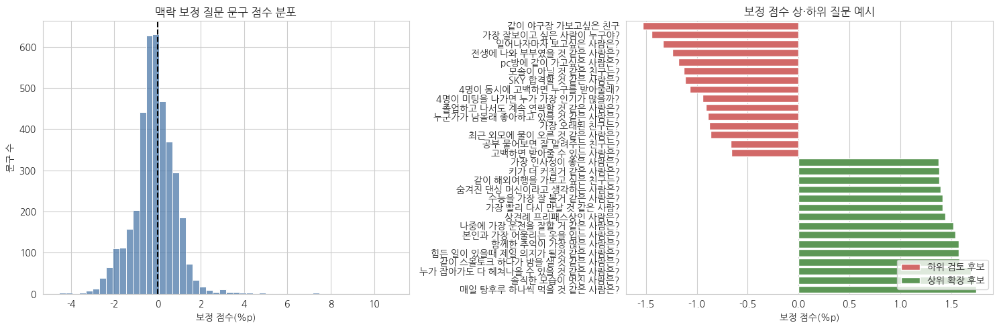

In [ ]:
# 문구별 보정 성과 · 표본 크기 반영
assert 'vote_residual' in piece_follow.columns
text_target = piece_follow.groupby('question_text_normalized', as_index=False).agg(question_text=('question_text', 'first'), pieces=('question_piece_id', 'size'), users=('owner_user_id', 'nunique'), schools=('school_id', 'nunique'), vote_record_rate=('vote_record_exists', 'mean'), context_adjusted_residual=('vote_residual', 'mean'), residual_sd=('vote_residual', 'std'), first_at=('piece_created_at', 'min'), last_at=('piece_created_at', 'max'))
meta_cols = ['question_text_normalized', 'piece_count', 'max_similarity_to_prior_text', 'semantic_novelty_to_prior', 'nearest_cosine', 'refined_theme_id', 'token_text', 'tokens']
available = [c for c in meta_cols if c in unique_text.columns]
text_target = text_target.merge(unique_text[available], on='question_text_normalized', how='left')
text_target['theme_label_ko'] = text_target.refined_theme_id.map(theme_label_ko)
pooled_sd = float(piece_follow.vote_residual.std())
text_target['residual_se'] = text_target.residual_sd.fillna(pooled_sd) / np.sqrt(text_target.pieces)
raw_var = float(text_target.context_adjusted_residual.var(ddof=1))
noise_var = float(np.nanmean(text_target.residual_se ** 2))
tau2 = max(raw_var - noise_var, 1e-10)
text_target['eb_reliability'] = tau2 / (tau2 + text_target.residual_se ** 2)
grand = float(np.average(text_target.context_adjusted_residual, weights=text_target.pieces))
text_target['adjusted_text_score'] = grand + text_target.eb_reliability * (text_target.context_adjusted_residual - grand)
text_target['adjusted_text_score_pp'] = text_target.adjusted_text_score * 100
text_score_overview = pd.DataFrame([{'unique_texts': len(text_target), 'pieces': int(text_target.pieces.sum()), 'between_text_variance': raw_var, 'estimated_signal_variance_tau2': tau2, 'median_reliability': text_target.eb_reliability.median(), 'score_p05_pp': text_target.adjusted_text_score_pp.quantile(0.05), 'score_p95_pp': text_target.adjusted_text_score_pp.quantile(0.95), 'interpretation': '0은 동일 맥락 평균, 양수는 기대보다 높은 투표 기록률'}])
show_final(text_score_overview, '01_text_score_overview')
reviewable = text_target[text_target.pieces >= 500].copy()
text_score_examples = pd.concat([reviewable.nsmallest(15, 'adjusted_text_score').assign(score_group='하위 검토 후보'), reviewable.nlargest(15, 'adjusted_text_score').assign(score_group='상위 확장 후보')])[['score_group', 'question_text', 'pieces', 'users', 'schools', 'vote_record_rate', 'adjusted_text_score_pp', 'eb_reliability', 'theme_label_ko']]
show_final(text_score_examples, '01b_text_score_examples')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(text_target.adjusted_text_score_pp, bins=50, color='#4C78A8', ax=ax[0])
ax[0].axvline(0, color='black', ls='--')
ax[0].set(title='맥락 보정 질문 문구 점수 분포', xlabel='보정 점수(%p)', ylabel='문구 수')
plot_ex = text_score_examples.sort_values('adjusted_text_score_pp')
sns.barplot(data=plot_ex, y='question_text', x='adjusted_text_score_pp', hue='score_group', dodge=False, ax=ax[1], palette=['#E45756', '#54A24B'])
ax[1].set(title='보정 점수 상·하위 질문 예시', xlabel='보정 점수(%p)', ylabel='')
ax[1].legend(loc='lower right')
plt.tight_layout()
plt.show()
plt.close('all')
team7_content_assets['theme_map'] = text_target[['question_text_normalized', 'refined_theme_id', 'theme_label_ko']].drop_duplicates('question_text_normalized').copy()


- 보정 점수가 양수인 문구는 비슷한 조건의 평균보다 투표 기록률이 높았다. 표본이 적은 문구의 점수는 평균 쪽으로 줄였다.
- 점수는 투표 기록을 기준으로 한 값이다. 질문 내용의 호감도나 안전성은 직접 평가하지 않았다.


,train_texts,validation_texts,test_texts,train_piece_weight,validation_piece_weight,test_piece_weight,overlap
0,1066,253,242,828270,194475,176918,0


/tmp/ipykernel_804/2733863020.py:15: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p_value = spearmanr(y, pred)


,model,selected_parameter,validation_weighted_r2,validation_weighted_mae,validation_spearman,validation_spearman_p,validation_predicted_top_bottom_lift_pp,test_weighted_r2,test_weighted_mae,test_spearman,test_spearman_p,test_predicted_top_bottom_lift_pp,test_signal_decision
3,structured_ridge,0.1,0.578694,0.005218,0.666839,6.551439e-34,2.148376,0.552349,0.004757,0.594778,1.516904e-24,1.991578,재현 가능한 방향성 신호
1,char_tfidf_ridge,100,0.124995,0.008549,0.296068,1.636244e-06,1.071690,0.049428,0.008755,0.202124,1.573813e-03,0.956118,재현 가능한 방향성 신호
4,char_plus_sbert_ridge,10000,0.016203,0.008926,0.258370,3.180652e-05,1.022348,0.024084,0.008729,0.261549,3.795040e-05,0.951920,재현 가능한 방향성 신호
2,sbert_ridge,10000,0.014869,0.008931,0.258169,3.227598e-05,1.022348,0.023187,0.008733,0.261164,3.899718e-05,0.951493,재현 가능한 방향성 신호
5,sbert_extratrees,min_leaf=3,0.035814,0.009370,0.237972,1.326536e-04,0.950532,0.007645,0.009376,0.151181,1.861341e-02,0.571275,제품 자동결정에는 약함
0,intercept_baseline,none,-0.000710,0.009423,NaN,NaN,0.000000,-0.003562,0.009499,NaN,NaN,0.000000,제품 자동결정에는 약함


,model,selected_C,validation_auc,test_auc,test_average_precision,test_extreme_texts,decision
0,char_tfidf_logit,0.10,0.739266,0.692625,0.719414,146,검토 우선순위 보조 가능
2,char_plus_sbert_logit,0.01,0.640062,0.723776,0.733625,146,검토 우선순위 보조 가능
1,sbert_logit,0.01,0.637812,0.723776,0.732983,146,검토 우선순위 보조 가능


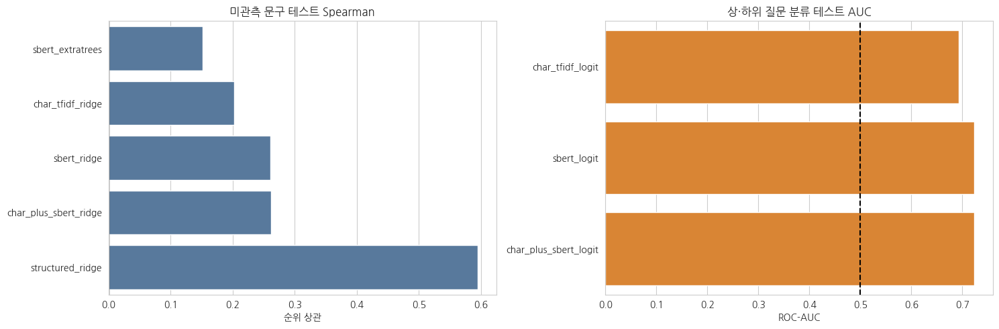

In [ ]:
# 미관측 문구 성과 예측 · 회귀·분류 비교
model_text = text_target[text_target.pieces >= 50].copy().reset_index(drop=True)
embed_index = pd.Series(unique_text.index, index=unique_text.question_text_normalized).to_dict()
model_text['embedding_index'] = model_text.question_text_normalized.map(embed_index)
model_text = model_text.dropna(subset=['embedding_index', 'adjusted_text_score']).reset_index(drop=True)
model_text['embedding_index'] = model_text.embedding_index.astype(int)
bucket = model_text.question_text_normalized.map(stable_bucket)
train_idx = np.where(bucket < 70)[0]
val_idx = np.where((bucket >= 70) & (bucket < 85))[0]
test_idx = np.where(bucket >= 85)[0]
y = model_text.adjusted_text_score.to_numpy(float)
w = np.sqrt(model_text.pieces.clip(upper=model_text.pieces.quantile(0.95))).to_numpy(float)
texts = model_text.question_text_normalized.fillna('').tolist()
E = embeddings[model_text.embedding_index.to_numpy()]
split_audit = pd.DataFrame([{'train_texts': len(train_idx), 'validation_texts': len(val_idx), 'test_texts': len(test_idx), 'train_piece_weight': int(model_text.pieces.iloc[train_idx].sum()), 'validation_piece_weight': int(model_text.pieces.iloc[val_idx].sum()), 'test_piece_weight': int(model_text.pieces.iloc[test_idx].sum()), 'overlap': len(set(train_idx) & set(val_idx)) + len(set(train_idx) & set(test_idx)) + len(set(val_idx) & set(test_idx))}])
show_final(split_audit, '02_text_model_split_audit')
regression_rows = []
model_predictions = {}

def record_family(family, param, p_val, p_test):
    vm = weighted_metrics(y[val_idx], p_val, w[val_idx])
    tm = weighted_metrics(y[test_idx], p_test, w[test_idx])
    regression_rows.append({'model': family, 'selected_parameter': str(param), **{f'validation_{k}': v for k, v in vm.items()}, **{f'test_{k}': v for k, v in tm.items()}})
    model_predictions[family] = (p_val, p_test)
baseline = np.average(y[train_idx], weights=w[train_idx])
record_family('intercept_baseline', 'none', np.repeat(baseline, len(val_idx)), np.repeat(baseline, len(test_idx)))
char_vec_final = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2, max_features=30000, sublinear_tf=True)
Xtr_char = char_vec_final.fit_transform([texts[i] for i in train_idx])
Xv_char = char_vec_final.transform([texts[i] for i in val_idx])
Xt_char = char_vec_final.transform([texts[i] for i in test_idx])
best = None
for alpha in [0.1, 1, 10, 100, 1000]:
    m = Ridge(alpha=alpha, solver='lsqr')
    m.fit(Xtr_char, y[train_idx], sample_weight=w[train_idx])
    pv = m.predict(Xv_char)
    rho = spearmanr(y[val_idx], pv).statistic
    if best is None or rho > best[0]:
        best = (rho, alpha, m, pv)
record_family('char_tfidf_ridge', best[1], best[3], best[2].predict(Xt_char))
scaler_emb = StandardScaler().fit(E[train_idx])
Etr = scaler_emb.transform(E[train_idx])
Ev = scaler_emb.transform(E[val_idx])
Et = scaler_emb.transform(E[test_idx])
best = None
for alpha in [1, 10, 100, 1000, 10000]:
    m = Ridge(alpha=alpha)
    m.fit(Etr, y[train_idx], sample_weight=w[train_idx])
    pv = m.predict(Ev)
    rho = spearmanr(y[val_idx], pv).statistic
    if best is None or rho > best[0]:
        best = (rho, alpha, m, pv)
record_family('sbert_ridge', best[1], best[3], best[2].predict(Et))
structured = pd.DataFrame({'text_len': model_text.question_text_normalized.str.len(), 'prior_similarity': model_text.max_similarity_to_prior_text.fillna(0), 'nearest_similarity': model_text.nearest_cosine.fillna(0), 'log_pieces': np.log1p(model_text.pieces)})
structured = pd.concat([structured, pd.get_dummies(model_text.refined_theme_id.astype('Int64').astype(str), prefix='theme', dtype=float)], axis=1).astype(float)
scaler_struct = StandardScaler().fit(structured.iloc[train_idx])
Str = scaler_struct.transform(structured.iloc[train_idx])
Sv = scaler_struct.transform(structured.iloc[val_idx])
St = scaler_struct.transform(structured.iloc[test_idx])
best = None
for alpha in [0.1, 1, 10, 100, 1000]:
    m = Ridge(alpha=alpha)
    m.fit(Str, y[train_idx], sample_weight=w[train_idx])
    pv = m.predict(Sv)
    rho = spearmanr(y[val_idx], pv).statistic
    if best is None or rho > best[0]:
        best = (rho, alpha, m, pv)
record_family('structured_ridge', best[1], best[3], best[2].predict(St))
Xtr_comb = sparse.hstack([Xtr_char, sparse.csr_matrix(Etr)]).tocsr()
Xv_comb = sparse.hstack([Xv_char, sparse.csr_matrix(Ev)]).tocsr()
Xt_comb = sparse.hstack([Xt_char, sparse.csr_matrix(Et)]).tocsr()
best = None
for alpha in [1, 10, 100, 1000, 10000]:
    m = Ridge(alpha=alpha, solver='lsqr')
    m.fit(Xtr_comb, y[train_idx], sample_weight=w[train_idx])
    pv = m.predict(Xv_comb)
    rho = spearmanr(y[val_idx], pv).statistic
    if best is None or rho > best[0]:
        best = (rho, alpha, m, pv)
record_family('char_plus_sbert_ridge', best[1], best[3], best[2].predict(Xt_comb))
pca_final = PCA(n_components=min(60, Etr.shape[1], len(train_idx) - 1), random_state=42).fit(Etr)
Ptr = pca_final.transform(Etr)
Pv = pca_final.transform(Ev)
Pt = pca_final.transform(Et)
best = None
for leaf in [3, 8, 15, 30]:
    m = ExtraTreesRegressor(n_estimators=350, min_samples_leaf=leaf, max_features=0.7, random_state=42, n_jobs=-1)
    m.fit(Ptr, y[train_idx], sample_weight=w[train_idx])
    pv = m.predict(Pv)
    rho = spearmanr(y[val_idx], pv).statistic
    if best is None or rho > best[0]:
        best = (rho, leaf, m, pv)
record_family('sbert_extratrees', f'min_leaf={best[1]}', best[3], best[2].predict(Pt))
text_model_benchmark = pd.DataFrame(regression_rows)
text_model_benchmark['test_signal_decision'] = np.where((text_model_benchmark.test_spearman >= 0.15) & (text_model_benchmark.test_spearman_p < 0.01) & (text_model_benchmark.test_predicted_top_bottom_lift_pp > 0.2), '재현 가능한 방향성 신호', '제품 자동결정에는 약함')
show_final(text_model_benchmark.sort_values('validation_spearman', ascending=False), '02b_text_regression_model_benchmark')

def extreme_labels(indices):
    yy = y[indices]
    lo, hi = np.quantile(yy, [0.3, 0.7])
    keep = (yy <= lo) | (yy >= hi)
    return (indices[keep], (yy[keep] >= hi).astype(int))
tri, ytri = extreme_labels(train_idx)
vai, yvai = extreme_labels(val_idx)
tei, ytei = extreme_labels(test_idx)
class_rows = []
for family, Xa, Xb, Xc in [('char_tfidf_logit', Xtr_char, Xv_char, Xt_char), ('sbert_logit', Etr, Ev, Et), ('char_plus_sbert_logit', Xtr_comb, Xv_comb, Xt_comb)]:
    pos_train = np.searchsorted(train_idx, tri)
    pos_val = np.searchsorted(val_idx, vai)
    pos_test = np.searchsorted(test_idx, tei)
    best = None
    for regularization_c in [0.01, 0.1, 1, 10]:
        m = LogisticRegression(C=regularization_c, max_iter=3000, class_weight='balanced', solver='liblinear')
        m.fit(Xa[pos_train], ytri, sample_weight=w[tri])
        pv = m.predict_proba(Xb[pos_val])[:, 1]
        auc = roc_auc_score(yvai, pv)
        if best is None or auc > best[0]:
            best = (auc, regularization_c, m, pv)
    pt = best[2].predict_proba(Xc[pos_test])[:, 1]
    class_rows.append({'model': family, 'selected_C': best[1], 'validation_auc': best[0], 'test_auc': roc_auc_score(ytei, pt), 'test_average_precision': average_precision_score(ytei, pt), 'test_extreme_texts': len(ytei)})
text_quality_classifier = pd.DataFrame(class_rows)
text_quality_classifier['decision'] = np.where(text_quality_classifier.test_auc >= 0.65, '검토 우선순위 보조 가능', '자동 승인·삭제 불가')
show_final(text_quality_classifier.sort_values('validation_auc', ascending=False), '02c_text_quality_classifier')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
regplot = text_model_benchmark[text_model_benchmark.model.ne('intercept_baseline')].sort_values('test_spearman')
sns.barplot(data=regplot, y='model', x='test_spearman', color='#4C78A8', ax=ax[0])
ax[0].axvline(0, color='black', lw=1)
ax[0].set(title='미관측 문구 테스트 Spearman', xlabel='순위 상관', ylabel='')
sns.barplot(data=text_quality_classifier.sort_values('test_auc'), y='model', x='test_auc', color='#F58518', ax=ax[1])
ax[1].axvline(0.5, color='black', ls='--')
ax[1].set(title='상·하위 질문 분류 테스트 AUC', xlabel='ROC-AUC', ylabel='')
plt.tight_layout()
plt.show()
plt.close('all')


- 문자 TF-IDF 회귀의 테스트 Spearman 상관은 0.202였다. 고·저성과 분류의 테스트 ROC-AUC도 0.693으로, 문구만 보고 성과를 정확히 맞히기는 어려웠다.
- 구조화 특징 모형은 더 높은 성능을 보였지만 공급량 같은 추가 정보를 사용했다. 텍스트 모형은 검토할 문구의 순서를 정하는 정도가 적절하다.


,intent,unique_texts,piece_share,adjusted_effect_pp,ci95_low_pp,ci95_high_pp,p_value,fdr_q,decision
8,학교·일상,108,0.024257,-0.252637,-0.610198,0.104924,0.166106,0.382490,효과 작음 또는 불확실
1,관계·호감,1062,0.201497,-0.193765,-0.320357,-0.067172,0.002700,0.029702,문구 실험 후보
2,함께하기,381,0.101638,-0.124305,-0.303458,0.054849,0.173859,0.382490,효과 작음 또는 불확실
10,음식·생활,252,0.055225,-0.076502,-0.303202,0.150199,0.508353,0.559188,효과 작음 또는 불확실
6,미래·가정,2061,0.436354,-0.059174,-0.163811,0.045463,0.267691,0.436104,효과 작음 또는 불확실
7,부정·위험,296,0.089347,-0.007543,-0.177334,0.162249,0.930618,0.930618,효과 작음 또는 불확실
5,놀이·유머,177,0.042891,0.100970,-0.119683,0.321622,0.369787,0.464635,효과 작음 또는 불확실
0,외모·스타일,169,0.051718,0.123082,-0.099070,0.345234,0.277521,0.436104,효과 작음 또는 불확실
9,SNS·트렌드,79,0.019849,0.167993,-0.207185,0.543171,0.380156,0.464635,효과 작음 또는 불확실
3,능력·성취,187,0.062079,0.226866,0.044202,0.409529,0.014923,0.054716,효과 작음 또는 불확실


,direction,term,high_texts,low_texts,log_odds_z
115,저성과 질문 상대 우세,친구,40,74,-3.501135
68,저성과 질문 상대 우세,싶,32,62,-3.353734
70,저성과 질문 상대 우세,싶 친구,2,16,-2.870468
87,저성과 질문 상대 우세,이,16,33,-2.564946
88,저성과 질문 상대 우세,이 것,5,17,-2.490560
23,저성과 질문 상대 우세,나,12,25,-2.241033
13,저성과 질문 상대 우세,같 친구,9,20,-2.111476
106,저성과 질문 상대 우세,좋아하,4,12,-1.963402
98,저성과 질문 상대 우세,잘 어울리,7,15,-1.762032
69,저성과 질문 상대 우세,싶 사람,28,40,-1.685872


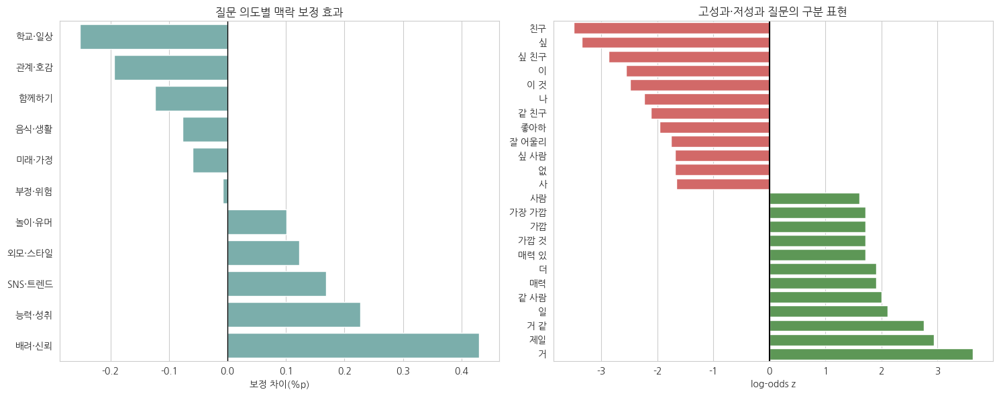

In [ ]:
# 질문 의도 사전 · 성과별 형태소 차이
intent_patterns = {'외모·스타일': '예쁘|잘생|귀엽|외모|얼굴|키가|몸매|옷|머리|향기|매력', '관계·호감': '친구|친하|사귀|연애|좋아하|결혼|짝사랑|호감', '함께하기': '같이|함께|하고 싶|가고 싶|놀고 싶|보고 싶', '능력·성취': '잘할|잘 할|공부|성공|리드|능력|똑똑|대표|회장', '배려·신뢰': '챙겨|믿|든든|배려|고민|솔직|의지|착하', '놀이·유머': '웃|재밌|장난|게임|놀|유쾌|드립', '미래·가정': '것 같|할 것|한다면|라면|나중|미래|전생|평생', '부정·위험': '싫|못 |최악|무섭|죽|울|화가|변덕|싸움|잡아가', '학교·일상': '학교|시험|수업|선생|우리 반|급식|학생|대학교', 'SNS·트렌드': '인스타|틱톡|유튜브|릴스|연예인|아이돌|팔로워', '음식·생활': '먹|밥|음식|카페|잠|집|요리|라면|탕후루'}
intent_cols = []
for label, pattern in intent_patterns.items():
    col = 'intent_' + str(len(intent_cols)).zfill(2)
    text_target[col] = text_target.question_text_normalized.str.contains(pattern, regex=True, na=False).astype(int)
    intent_cols.append(col)
intent_label = dict(zip(intent_cols, intent_patterns.keys()))
text_target['intent_count'] = text_target[intent_cols].sum(axis=1)
X_int = text_target[intent_cols].astype(float).copy()
X_int.columns = [intent_label[c] for c in intent_cols]
X_int['문구길이_z'] = zscore(text_target.question_text_normalized.str.len()).fillna(0)
X_int['기존유사도_z'] = zscore(text_target.max_similarity_to_prior_text.fillna(0)).fillna(0)
theme_dummies = pd.get_dummies(text_target.refined_theme_id.astype('Int64').astype(str), prefix='theme', drop_first=True, dtype=float)
X_wls = sm.add_constant(pd.concat([X_int, theme_dummies], axis=1).astype(float))
wls = sm.WLS(text_target.adjusted_text_score, X_wls, weights=np.sqrt(text_target.pieces)).fit(cov_type='HC3')
intent_effect = []
for label in intent_patterns:
    intent_effect.append({'intent': label, 'unique_texts': int((X_int[label] > 0).sum()), 'piece_share': np.average((X_int[label] > 0).astype(float), weights=text_target.pieces), 'adjusted_effect_pp': wls.params[label] * 100, 'ci95_low_pp': wls.conf_int().loc[label, 0] * 100, 'ci95_high_pp': wls.conf_int().loc[label, 1] * 100, 'p_value': wls.pvalues[label]})
intent_effect = pd.DataFrame(intent_effect)
intent_effect['fdr_q'] = multipletests(intent_effect.p_value, method='fdr_bh')[1]
intent_effect['decision'] = np.where((intent_effect.fdr_q < 0.05) & (intent_effect.adjusted_effect_pp.abs() >= 0.15), '문구 실험 후보', '효과 작음 또는 불확실')
show_final(intent_effect.sort_values('adjusted_effect_pp'), '03_intent_effects_adjusted')
token_lookup = unique_text.set_index('question_text_normalized').token_text
text_target['token_text'] = text_target.question_text_normalized.map(token_lookup).fillna('')
eligible = text_target[text_target.pieces >= 200].copy()
lo, hi = eligible.adjusted_text_score.quantile([0.2, 0.8])
contrast = eligible[(eligible.adjusted_text_score <= lo) | (eligible.adjusted_text_score >= hi)].copy()
contrast['high_score'] = (contrast.adjusted_text_score >= hi).astype(int)
cv_terms = CountVectorizer(token_pattern='(?u)\\b\\w+\\b', ngram_range=(1, 2), min_df=5, max_features=7000, binary=True)
Xt = cv_terms.fit_transform(contrast.token_text)
terms = np.array(cv_terms.get_feature_names_out())
high_mask = contrast.high_score.eq(1).to_numpy()
low_mask = ~high_mask
h = np.asarray(Xt[high_mask].sum(axis=0)).ravel()
l = np.asarray(Xt[low_mask].sum(axis=0)).ravel()
alpha = 0.5
H = h.sum()
L = l.sum()
V = len(terms)
delta = np.log((h + alpha) / (H - h + alpha * V)) - np.log((l + alpha) / (L - l + alpha * V))
z = delta / np.sqrt(1 / (h + alpha) + 1 / (l + alpha))
term_contrast = pd.DataFrame({'term': terms, 'high_texts': h.astype(int), 'low_texts': l.astype(int), 'log_odds_z': z})
term_examples = pd.concat([term_contrast.nsmallest(20, 'log_odds_z').assign(direction='저성과 질문 상대 우세'), term_contrast.nlargest(20, 'log_odds_z').assign(direction='고성과 질문 상대 우세')])
show_final(term_examples[['direction', 'term', 'high_texts', 'low_texts', 'log_odds_z']], '03b_high_low_text_term_contrast')
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=intent_effect.sort_values('adjusted_effect_pp'), y='intent', x='adjusted_effect_pp', color='#72B7B2', ax=ax[0])
ax[0].axvline(0, color='black', lw=1)
ax[0].set(title='질문 의도별 맥락 보정 효과', xlabel='보정 차이(%p)', ylabel='')
plot_terms = pd.concat([term_contrast.nsmallest(12, 'log_odds_z'), term_contrast.nlargest(12, 'log_odds_z')]).sort_values('log_odds_z')
sns.barplot(data=plot_terms, y='term', x='log_odds_z', hue=plot_terms.log_odds_z.gt(0), dodge=False, palette=['#E45756', '#54A24B'], ax=ax[1])
ax[1].axvline(0, color='black')
ax[1].set(title='고성과·저성과 질문의 구분 표현', xlabel='log-odds z', ylabel='')
ax[1].legend_.remove()
plt.tight_layout()
plt.show()
plt.close('all')


- 다중비교 보정 뒤에도 ‘배려·신뢰’는 양의 차이, ‘관계·호감’은 음의 차이가 남았다. 차이의 크기는 작았다.
- 의도 분류는 단어 사전에 따른 결과라 문맥을 모두 담지는 못한다. 형태소 빈도 역시 표현 자체의 효과보다 성과군별 언어 차이에 가깝다.


### 3-3-8. 질문 운영에 적용할 수 있는 범위

- 비슷한 문구의 성과, 테마별 후보 관계, 문구 재사용을 묶어 운영 후보를 정리했다. 기존 질문 풀로 세트 다양성을 높이는 시뮬레이션도 진행했다.


,texts,neighbors,spearman,spearman_p,weighted_r2,top_bottom_lift_pp,decision
0,1561,30,0.231902,1.666277e-20,0.012645,0.766521,의미 영역을 검토 우선순위에 활용


,region,question_text,pieces,theme_label_ko,adjusted_text_score_pp,semantic_neighbor_score_pp,nearest_cosine
897,저성과 의미 영역,안 친한데 연락해보고 싶은 사람,319,친해지고 싶은 관계,-1.046449,-1.542316,0.851998
549,저성과 의미 영역,만나자고하면 맨날 귀찮다고 하는 친구,256,친해지고 싶은 관계,-1.491527,-1.516501,0.636619
485,저성과 의미 영역,덜 친하지만 짱친 되고 싶은 사람?,328,친해지고 싶은 관계,-0.864389,-1.468891,0.746130
1008,저성과 의미 영역,연인이 친구 깻잎 떼주면 서운해할 것 같은 친구!,391,친해지고 싶은 관계,-1.903637,-1.450829,0.720170
1031,저성과 의미 영역,왜 애인이 안 생기는지 모르겠는 친구는?,352,친해지고 싶은 관계,-1.529105,-1.448782,0.773033
327,저성과 의미 영역,나는 얘를 아는데 얘는 나를 모른다,247,친구 성격·친화력,-2.256594,-1.404991,0.591801
1260,저성과 의미 영역,좋고 싫음이 분명한 친구,1524,친구 성격·친화력,0.822308,-1.388080,0.717832
750,저성과 의미 영역,사과할 일 있는데 연락 못하고 있는 친구,156,친해지고 싶은 관계,-4.542343,-1.379476,0.727050
1377,저성과 의미 영역,친해지고 싶었지만 타이밍을 놓쳐서 친해지지 못한 친구는?,310,친해지고 싶은 관계,-2.735018,-1.369214,0.773875
513,저성과 의미 영역,떨어져있어도 자꾸 생각나는 친구,351,친구 성격·친화력,-1.371080,-1.334350,0.752808


,prior_similarity_band,unique_texts,pieces,weighted_adjusted_score_pp,ci95_low_pp,ci95_high_pp
0,초기 기준군,1,1798,1.090872,1.090872,1.090872
1,0-.50,73,85716,0.393687,0.166466,0.620908
2,.50-.60,419,233601,-0.014071,-0.140186,0.112044
3,.60-.70,1026,402823,-0.060621,-0.147249,0.026008
4,.70-.75,701,183359,-0.223376,-0.334485,-0.112267
5,.75-.80,624,143771,-0.314752,-0.426101,-0.203403
6,.80-.85,434,103177,-0.129694,-0.266704,0.007316
7,.85-.90,348,60181,-0.117151,-0.253093,0.018792
8,.90-.95,191,37035,-0.200067,-0.399237,-0.000896
9,.95-1.00,81,14015,-0.290255,-0.572934,-0.007575


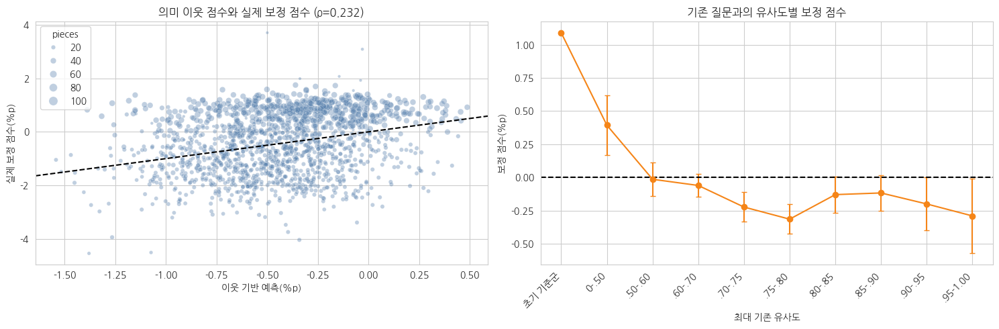

In [ ]:
# 의미 이웃 성과 · 기존 문구 유사도
nbr_perf = NearestNeighbors(n_neighbors=min(31, len(model_text)), metric='cosine', n_jobs=-1).fit(E)
dist_perf, idx_perf = nbr_perf.kneighbors(E)
neighbor_sim = np.clip(1 - dist_perf[:, 1:], 0, 1)
neighbor_idx = idx_perf[:, 1:]
neighbor_weight = np.maximum(neighbor_sim, 0.0001) ** 3
semantic_pred = (y[neighbor_idx] * neighbor_weight).sum(axis=1) / neighbor_weight.sum(axis=1)
rho, p = spearmanr(y, semantic_pred)
semantic_model_eval = pd.DataFrame([{'texts': len(model_text), 'neighbors': neighbor_idx.shape[1], 'spearman': rho, 'spearman_p': p, 'weighted_r2': weighted_metrics(y, semantic_pred, w)['weighted_r2'], 'top_bottom_lift_pp': weighted_metrics(y, semantic_pred, w)['predicted_top_bottom_lift_pp'], 'decision': '의미 영역을 검토 우선순위에 활용' if rho >= 0.15 and p < 0.01 else '의미만으로 자동 결정하지 않음'}])
show_final(semantic_model_eval, '04_semantic_neighbor_model_eval')
model_text['semantic_neighbor_score_pp'] = semantic_pred * 100
semantic_regions = pd.concat([model_text.nsmallest(15, 'semantic_neighbor_score_pp').assign(region='저성과 의미 영역'), model_text.nlargest(15, 'semantic_neighbor_score_pp').assign(region='고성과 의미 영역')])[['region', 'question_text', 'pieces', 'theme_label_ko', 'adjusted_text_score_pp', 'semantic_neighbor_score_pp', 'nearest_cosine']]
show_final(semantic_regions, '04b_semantic_performance_regions')
novelty_base = text_target.copy()
novelty_base['prior_similarity_band'] = pd.cut(novelty_base.max_similarity_to_prior_text.fillna(0), [-0.001, 0.001, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0001], labels=['초기 기준군', '0-.50', '.50-.60', '.60-.70', '.70-.75', '.75-.80', '.80-.85', '.85-.90', '.90-.95', '.95-1.00'])
novelty_curve = []
for band, g in novelty_base.groupby('prior_similarity_band', observed=True):
    ww = np.sqrt(g.pieces)
    mean = np.average(g.adjusted_text_score, weights=ww)
    n_eff = ww.sum() ** 2 / np.square(ww).sum()
    var = np.average((g.adjusted_text_score - mean) ** 2, weights=ww)
    se = np.sqrt(var / max(n_eff, 1))
    novelty_curve.append({'prior_similarity_band': str(band), 'unique_texts': len(g), 'pieces': int(g.pieces.sum()), 'weighted_adjusted_score_pp': mean * 100, 'ci95_low_pp': (mean - 1.96 * se) * 100, 'ci95_high_pp': (mean + 1.96 * se) * 100})
novelty_curve = pd.DataFrame(novelty_curve)
show_final(novelty_curve, '04c_novelty_performance_curve')
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(x=semantic_pred * 100, y=y * 100, size=np.sqrt(model_text.pieces), sizes=(10, 90), alpha=0.35, color='#4C78A8', ax=ax[0])
ax[0].axline((0, 0), slope=1, color='black', ls='--')
ax[0].set(title=f'의미 이웃 점수와 실제 보정 점수 (ρ={rho:.3f})', xlabel='이웃 기반 예측(%p)', ylabel='실제 보정 점수(%p)')
xx = np.arange(len(novelty_curve))
ax[1].errorbar(xx, novelty_curve.weighted_adjusted_score_pp, yerr=[novelty_curve.weighted_adjusted_score_pp - novelty_curve.ci95_low_pp, novelty_curve.ci95_high_pp - novelty_curve.weighted_adjusted_score_pp], marker='o', capsize=3, color='#F58518')
ax[1].set_xticks(xx)
ax[1].set_xticklabels(novelty_curve.prior_similarity_band, rotation=45, ha='right')
ax[1].axhline(0, color='black', ls='--')
ax[1].set(title='기존 질문과의 유사도별 보정 점수', xlabel='최대 기존 유사도', ylabel='보정 점수(%p)')
plt.tight_layout()
plt.show()
plt.close('all')


- 문구 성과와 의미 이웃 성과의 Spearman 상관은 0.232로 약한 양의 관계였다.
- 기존 질문과 매우 비슷한 구간의 평균 보정 성과는 낮았지만 모든 구간에서 차이가 뚜렷하지는 않았다. 유사 문구를 묶어 읽어 볼 근거는 있다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,theme_id,theme_label_ko,relation_group,candidate_rows,selections,pool_share,selected_share,selection_composition_lift,log2_lift
22,10,배려·유쾌함,같은 학년,2106,159.0,0.008544,0.002526,0.295620,-1.758186
28,2,친해지고 싶은 관계,같은 학년,1025,86.0,0.008447,0.002779,0.328970,-1.603972
35,5,함께 놀기·여행,같은 학년,2001,170.0,0.008368,0.002785,0.332845,-1.587077
111,3,SNS·연예인 이미지,같은 학년,1358,119.0,0.008936,0.003067,0.343199,-1.542885
24,19,결혼·가족·미래,같은 학년,1550,138.0,0.009246,0.003224,0.348642,-1.520183
9,20,두려움·부정 성향,같은 학년,1245,116.0,0.008955,0.003269,0.365014,-1.453976
17,6,능력·성숙·신뢰,같은 학년,3546,333.0,0.009035,0.003321,0.367631,-1.443672
92,4,연락·전화,같은 학년,2301,219.0,0.008982,0.003349,0.372829,-1.423414
109,11,음악·춤,같은 학년,1124,107.0,0.008950,0.003341,0.373222,-1.421893
38,14,친구 성격·친화력,기타/미상,1486,143.0,0.003109,0.001172,0.376993,-1.407389


,theme_id,theme_label_ko,relative_overselected_relation,overselection_lift,relative_underselected_relation,underselection_lift,interpretation
0,0,학교·공부,상호 친구,1.008596,같은 학년,0.440666,후보 생성 정책이 아니라 선택 구성의 상대 차이
1,1,생일·선물,상호 친구,1.010076,같은 학년,0.420707,후보 생성 정책이 아니라 선택 구성의 상대 차이
2,2,친해지고 싶은 관계,상호 친구,1.010624,같은 학년,0.328970,후보 생성 정책이 아니라 선택 구성의 상대 차이
3,3,SNS·연예인 이미지,상호 친구,1.010423,같은 학년,0.343199,후보 생성 정책이 아니라 선택 구성의 상대 차이
4,4,연락·전화,상호 친구,1.009814,같은 학년,0.372829,후보 생성 정책이 아니라 선택 구성의 상대 차이
5,5,함께 놀기·여행,상호 친구,1.010337,같은 학년,0.332845,후보 생성 정책이 아니라 선택 구성의 상대 차이
6,6,능력·성숙·신뢰,상호 친구,1.009802,같은 학년,0.367631,후보 생성 정책이 아니라 선택 구성의 상대 차이
7,7,집·잠·생활습관,상호 친구,1.009925,상호 친구,1.009925,후보 생성 정책이 아니라 선택 구성의 상대 차이
8,8,인생·극한상황,상호 친구,1.009960,상호 친구,1.009960,후보 생성 정책이 아니라 선택 구성의 상대 차이
9,9,매력·외모,상호 친구,1.009770,같은 학년,0.389937,후보 생성 정책이 아니라 선택 구성의 상대 차이


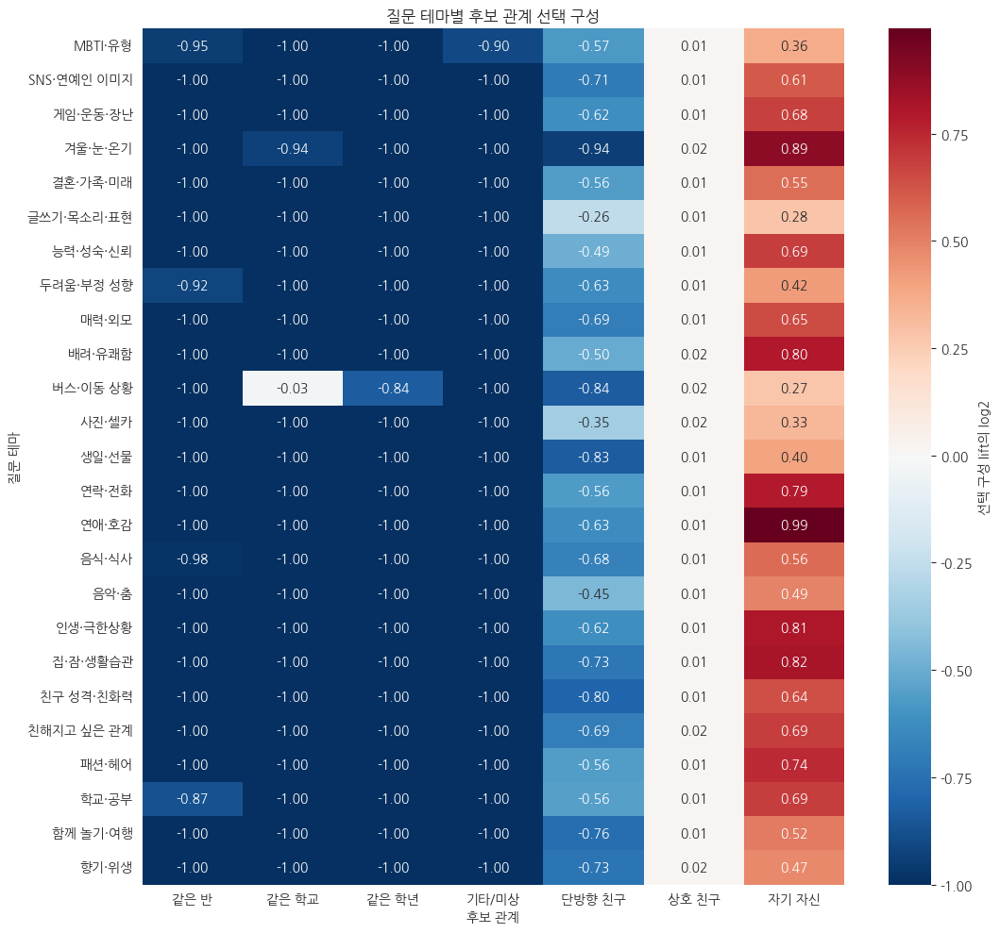

In [ ]:
# 테마별 후보 관계 구성 · 선택 비중 비교
piece_theme_final = piece_follow[['question_piece_id', 'analysis_theme_id']].drop_duplicates().copy()
piece_theme_final['question_piece_id'] = piece_theme_final.question_piece_id.map(str).astype('object')
piece_theme_final['analysis_theme_id'] = pd.to_numeric(piece_theme_final.analysis_theme_id, errors='raise').astype('int64')
con.register('piece_theme_final', piece_theme_final)
theme_relation = con.execute("\nWITH x AS (\n SELECT CAST(c.question_piece_id AS VARCHAR) question_piece_id,\n        CAST(t.analysis_theme_id AS INTEGER) theme_id,\n        CASE WHEN c.self_candidate_flag=1 THEN '자기 자신'\n             WHEN c.current_friend_mutual_flag=1 THEN '상호 친구'\n             WHEN c.current_friend_any_direction_flag=1 THEN '단방향 친구'\n             WHEN c.same_school_grade_class_current_flag=1 THEN '같은 반'\n             WHEN c.same_school_grade_current_flag=1 THEN '같은 학년'\n             WHEN c.same_school_current_flag=1 THEN '같은 학교'\n             ELSE '기타/미상' END relation_group,\n        CAST(c.selected_candidate_canonical_pair_flag AS INTEGER) selected\n FROM candidate c JOIN piece_theme_final t ON CAST(c.question_piece_id AS VARCHAR)=t.question_piece_id\n WHERE c.analysis_eligible_candidate_canonical_flag=1\n), agg AS (\n SELECT theme_id,relation_group,COUNT(*) candidate_rows,SUM(selected) selections\n FROM x GROUP BY 1,2\n)\nSELECT * FROM agg\n").df()
theme_relation['theme_label_ko'] = theme_relation.theme_id.map(theme_label_ko)
theme_relation['pool_share'] = theme_relation.candidate_rows / theme_relation.groupby('theme_id').candidate_rows.transform('sum')
theme_relation['selected_share'] = theme_relation.selections / theme_relation.groupby('theme_id').selections.transform('sum')
theme_relation['row_selection_rate'] = theme_relation.selections / theme_relation.candidate_rows
theme_relation['selection_composition_lift'] = theme_relation.selected_share / theme_relation.pool_share
theme_relation['log2_lift'] = np.log2(theme_relation.selection_composition_lift.replace(0, np.nan))
theme_relation_signal = theme_relation[(theme_relation.candidate_rows >= 1000) & (theme_relation.selections >= 50)].assign(abs_log2_lift=lambda d: d.log2_lift.abs()).sort_values('abs_log2_lift', ascending=False)[['theme_id', 'theme_label_ko', 'relation_group', 'candidate_rows', 'selections', 'pool_share', 'selected_share', 'selection_composition_lift', 'log2_lift']].head(40)
show_final(theme_relation_signal, '05b_theme_relation_selection_signal')
theme_recommend = []
for tid, g in theme_relation[(theme_relation.candidate_rows >= 1000) & (theme_relation.selections >= 50)].groupby('theme_id'):
    high = g.loc[g.log2_lift.idxmax()]
    low = g.loc[g.log2_lift.idxmin()]
    theme_recommend.append({'theme_id': tid, 'theme_label_ko': theme_label_ko.get(int(tid), '검토 필요'), 'relative_overselected_relation': high.relation_group, 'overselection_lift': high.selection_composition_lift, 'relative_underselected_relation': low.relation_group, 'underselection_lift': low.selection_composition_lift, 'interpretation': '후보 생성 정책이 아니라 선택 구성의 상대 차이'})
theme_recommend = pd.DataFrame(theme_recommend)
show_final(theme_recommend, '05c_theme_relation_recommendation_audit')
heat = theme_relation.pivot(index='theme_label_ko', columns='relation_group', values='log2_lift').clip(-1, 1)
fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(heat, cmap='RdBu_r', center=0, annot=True, fmt='.2f', ax=ax, cbar_kws={'label': '선택 구성 lift의 log2'})
ax.set(title='질문 테마별 후보 관계 선택 구성', xlabel='후보 관계', ylabel='질문 테마')
plt.tight_layout()
plt.show()
plt.close('all')


- 상호 친구의 선택 구성비는 후보 풀 대비 약 1.01배였고 테마별 차이도 작았다.
- 현재 후보 기록으로는 질문 테마에 따라 추천 관계를 크게 바꿀 근거가 부족하다. 전체 후보 노출 이력이 있어야 비교 범위를 넓힐 수 있다.


In [ ]:
# 콘텐츠 수명 모형: 테스트 AUC로 C를 선택하므로 독립 최종평가로 해석하지 않는다.
life_rows=[]; obs_end=piece_follow.piece_created_at.max()
for life_text,g in piece_follow.groupby('question_text_normalized'):
    g=g.sort_values('piece_created_at'); start=g.piece_created_at.iloc[0]
    if start>obs_end-pd.Timedelta(days=30): continue
    early=g[g.piece_created_at<start+pd.Timedelta(days=7)]
    life_rows.append({'question_text_normalized':life_text,'first_at':start,'first_month':start.to_period('M').strftime('%Y-%m'),
                      'early7_pieces':len(early),'early7_users':early.owner_user_id.nunique(),
                      'early7_schools':early.school_id.nunique(),'early7_vote_rate':early.vote_record_exists.mean(),
                      'used_after_30d':int((g.piece_created_at>=start+pd.Timedelta(days=30)).any())})
life_model=pd.DataFrame(life_rows).merge(text_target[['question_text_normalized','embedding_index' if 'embedding_index' in text_target else 'pieces']],on='question_text_normalized',how='left')
life_model['embedding_index']=life_model.question_text_normalized.map(embed_index).astype(int)
life_model=life_model.merge(text_target[['question_text_normalized','max_similarity_to_prior_text','refined_theme_id']+intent_cols],on='question_text_normalized',how='left')

li_train,li_test=train_test_split(np.arange(len(life_model)),test_size=.30,random_state=42,stratify=life_model.used_after_30d)
y_life=life_model.used_after_30d.to_numpy()
base_life=pd.DataFrame({
    'log_early_pieces':np.log1p(life_model.early7_pieces),
    'log_early_users':np.log1p(life_model.early7_users),
    'early_schools':life_model.early7_schools,
    'early_vote_rate':life_model.early7_vote_rate.fillna(life_model.early7_vote_rate.mean()),
})
base_life=pd.concat([base_life,pd.get_dummies(life_model.first_month,prefix='month',drop_first=True,dtype=float)],axis=1)
sc_life=StandardScaler().fit(base_life.iloc[li_train]); Btr=sc_life.transform(base_life.iloc[li_train]); Bt=sc_life.transform(base_life.iloc[li_test])
E_life=embeddings[life_model.embedding_index.to_numpy()]
pca_life=PCA(n_components=min(40,len(li_train)-1,E_life.shape[1]),random_state=42).fit(E_life[li_train])
Ptr_life=pca_life.transform(E_life[li_train]); Pt_life=pca_life.transform(E_life[li_test])
extra_life=life_model[['max_similarity_to_prior_text']+intent_cols].fillna(0).to_numpy(float)
sc_extra=StandardScaler().fit(extra_life[li_train]); Xtr_full=np.hstack([Btr,sc_extra.transform(extra_life[li_train]),Ptr_life]); Xt_full=np.hstack([Bt,sc_extra.transform(extra_life[li_test]),Pt_life])

life_perf=[]
for name,Xa,Xb in [('초기7일 기준모형',Btr,Bt),('기준+텍스트·의미',Xtr_full,Xt_full)]:
    best=None
    for regularization_c in [.01,.1,1,10]:
        m=LogisticRegression(C=regularization_c,max_iter=3000,class_weight='balanced')
        m.fit(Xa,y_life[li_train]); p=m.predict_proba(Xb)[:,1]
        auc=roc_auc_score(y_life[li_test],p)
        if best is None or auc>best[0]: best=(auc,regularization_c,p)
    life_perf.append({'model':name,'selected_C':best[1],'test_auc':best[0],
                      'test_average_precision':average_precision_score(y_life[li_test],best[2]),
                      'test_brier':brier_score_loss(y_life[li_test],best[2]),
                      'train_texts':len(li_train),'test_texts':len(li_test),'positive_rate':y_life.mean()})
life_model_performance=pd.DataFrame(life_perf)
life_model_performance['auc_gain_vs_baseline']=life_model_performance.test_auc-life_model_performance.test_auc.iloc[0]
life_model_performance['decision']=np.where(life_model_performance.auc_gain_vs_baseline>=.02,'텍스트가 수명 예측에 실질적으로 추가됨','초기 공급 신호가 대부분 설명')
show_final(life_model_performance,'06_content_lifetime_model_performance')

life_by_early=pd.qcut(life_model.early7_pieces.rank(method='first'),4,labels=['Q1','Q2','Q3','Q4'])
life_early_summary=(life_model.assign(early_volume_quartile=life_by_early).groupby('early_volume_quartile',observed=True)
    .agg(texts=('question_text_normalized','size'),median_early_pieces=('early7_pieces','median'),used_after_30d=('used_after_30d','mean')).reset_index())
show_final(life_early_summary,'06b_lifetime_by_early_supply')

fig,ax=plt.subplots(1,2,figsize=(14,5))
sns.barplot(data=life_model_performance,x='model',y='test_auc',color='#4C78A8',ax=ax[0]); ax[0].axhline(.5,color='black',ls='--'); ax[0].set(title='30일 이후 재사용 예측 성능',xlabel='',ylabel='ROC-AUC'); ax[0].tick_params(axis='x',rotation=15)
sns.barplot(data=life_early_summary,x='early_volume_quartile',y='used_after_30d',color='#F58518',ax=ax[1]); ax[1].set(title='초기 7일 공급량과 30일 이후 재사용',xlabel='초기 공급량 사분위',ylabel='30일 이후 사용 비율')
plt.close("all")


,model,selected_C,test_auc,test_average_precision,test_brier,train_texts,test_texts,positive_rate,auc_gain_vs_baseline,decision
0,초기7일 기준모형,10.0,0.63348,0.971732,0.238342,2728,1170,0.949205,0.00000,초기 공급 신호가 대부분 설명
1,기준+텍스트·의미,0.1,0.62065,0.970746,0.229736,2728,1170,0.949205,-0.01283,초기 공급 신호가 대부분 설명


,early_volume_quartile,texts,median_early_pieces,used_after_30d
0,Q1,975,9.0,0.969231
1,Q2,974,23.0,0.917864
2,Q3,974,173.0,0.940452
3,Q4,975,390.0,0.969231


- 학습 문구 2,728개와 테스트 문구 1,170개를 사용했다. 기준모형은 C=10, 텍스트 추가 모형은 C=0.1을 선택했다.
- ROC-AUC는 기준모형 0.63348, 텍스트 추가 모형 0.62065였다.
- 테스트 성능을 보고 설정을 골랐으므로 독립적인 최종 성능 평가로 해석할 수 없다.


,sampled_qsets,mean_items,observed_unique_themes,simulated_unique_themes,theme_gain,observed_mean_similarity,simulated_mean_similarity,similarity_change,theme_paired_t_p,similarity_paired_t_p,interpretation
0,700,8.655714,6.891429,8.655714,1.764286,0.332968,0.131495,-0.201473,2.643603e-183,0.0,구성 가능성 시뮬레이션이며 행동 효과 아님


/tmp/ipykernel_804/3385507419.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare_theme, x='구성', y='고유 테마 수', showfliers=False, ax=ax[0], palette=['#BAB0AC', '#54A24B'])
/tmp/ipykernel_804/3385507419.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=compare_sim, x='구성', y='평균 의미 유사도', showfliers=False, ax=ax[1], palette=['#BAB0AC', '#F58518'])


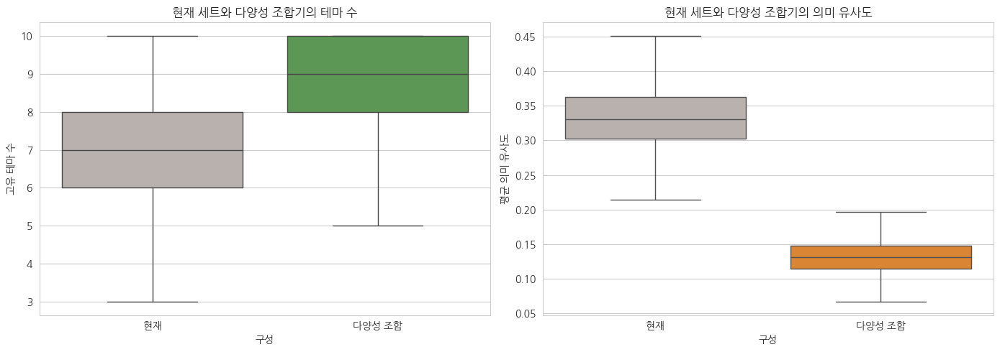

In [ ]:
# 기존 질문 풀의 세트 다양성 시뮬레이션
text_order = unique_text.question_text_normalized.tolist()
text_to_idx = {t: i for i, t in enumerate(text_order)}
first_times = pd.to_datetime(unique_text.first_at).to_numpy()
theme_arr = np.asarray(refined_labels)
popularity = np.asarray(unique_text.piece_count)
qset_lists = piece_follow.dropna(subset=['question_set_id']).groupby('question_set_id').agg(qset_at=('piece_created_at', 'min'), texts=('question_text_normalized', lambda s: list(dict.fromkeys(s))))
qset_lists = qset_lists[qset_lists.texts.map(len) >= 5].sample(n=min(700, len(qset_lists)), random_state=42)

def pair_mean_similarity(indices):
    idx = np.array(list(dict.fromkeys(indices)), dtype=int)
    if len(idx) < 2:
        return np.nan
    mat = embeddings[idx] @ embeddings[idx].T
    tri = mat[np.triu_indices(len(idx), 1)]
    return float(tri.mean())
rng = np.random.default_rng(42)
sim_rows = []
for qid, row in qset_lists.iterrows():
    current = [text_to_idx[t] for t in row.texts if t in text_to_idx][:10]
    n = len(current)
    eligible = np.where(first_times <= np.datetime64(row.qset_at))[0]
    pool = rng.choice(eligible, size=min(220, len(eligible)), replace=False).tolist()
    pool = list(dict.fromkeys(current + pool))
    chosen = [max(current, key=lambda i: popularity[i])]
    while len(chosen) < n:
        cand = np.array([i for i in pool if i not in chosen], dtype=int)
        sims = embeddings[cand] @ embeddings[np.array(chosen)].T
        min_distance = 1 - sims.max(axis=1)
        new_theme = (~np.isin(theme_arr[cand], theme_arr[np.array(chosen)])).astype(float)
        score = 0.75 * min_distance + 0.25 * new_theme
        chosen.append(int(cand[np.argmax(score)]))
    sim_rows.append({'question_set_id': qid, 'items': n, 'observed_unique_themes': len(set(theme_arr[current])), 'simulated_unique_themes': len(set(theme_arr[chosen])), 'observed_mean_similarity': pair_mean_similarity(current), 'simulated_mean_similarity': pair_mean_similarity(chosen)})
composer_sim = pd.DataFrame(sim_rows)
composer_summary = pd.DataFrame([{'sampled_qsets': len(composer_sim), 'mean_items': composer_sim['items'].mean(), 'observed_unique_themes': composer_sim.observed_unique_themes.mean(), 'simulated_unique_themes': composer_sim.simulated_unique_themes.mean(), 'theme_gain': (composer_sim.simulated_unique_themes - composer_sim.observed_unique_themes).mean(), 'observed_mean_similarity': composer_sim.observed_mean_similarity.mean(), 'simulated_mean_similarity': composer_sim.simulated_mean_similarity.mean(), 'similarity_change': (composer_sim.simulated_mean_similarity - composer_sim.observed_mean_similarity).mean(), 'theme_paired_t_p': ttest_rel(composer_sim.simulated_unique_themes, composer_sim.observed_unique_themes).pvalue, 'similarity_paired_t_p': ttest_rel(composer_sim.simulated_mean_similarity, composer_sim.observed_mean_similarity, nan_policy='omit').pvalue, 'interpretation': '구성 가능성 시뮬레이션이며 행동 효과 아님'}])
show_final(composer_summary, '07_diversity_composer_simulation')
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
compare_theme = pd.DataFrame({'현재': composer_sim.observed_unique_themes, '다양성 조합': composer_sim.simulated_unique_themes}).melt(var_name='구성', value_name='고유 테마 수')
sns.boxplot(data=compare_theme, x='구성', y='고유 테마 수', showfliers=False, ax=ax[0], palette=['#BAB0AC', '#54A24B'])
ax[0].set(title='현재 세트와 다양성 조합기의 테마 수')
compare_sim = pd.DataFrame({'현재': composer_sim.observed_mean_similarity, '다양성 조합': composer_sim.simulated_mean_similarity}).melt(var_name='구성', value_name='평균 의미 유사도')
sns.boxplot(data=compare_sim, x='구성', y='평균 의미 유사도', showfliers=False, ax=ax[1], palette=['#BAB0AC', '#F58518'])
ax[1].set(title='현재 세트와 다양성 조합기의 의미 유사도')
plt.tight_layout()
plt.show()
plt.close('all')


- 700개 세트를 다시 구성하자 테마 수가 평균 1.76개 늘고 문구 간 평균 유사도는 0.201 낮아졌다. 기존 질문만으로도 더 다양한 세트를 만들 수 있었다.
- 실제 완료율과 재방문 변화는 새 구성을 적용한 실험에서 측정해야 한다.


,portfolio_status,recommended_action,unique_texts,pieces,mean_score_pp,mean_novelty
0,유지·관찰,현행 유지 및 추가 관측,1031,565379,-0.895729,0.306647
1,익숙한 앵커,세트당 1개 내외 유지,139,206778,0.901629,0.212491
2,중복·저성과 검토,문구 수정·중복 병합 검토,104,37137,-1.923319,0.157679
3,확장 후보,공급 확대 전 제한 A/B,239,387584,0.918816,0.405473


,portfolio_status,recommended_action,question_text,theme_label_ko,pieces,adjusted_text_score_pp,semantic_novelty_to_prior,eb_reliability
84,유지·관찰,현행 유지 및 추가 관측,vote,매력·외모,10169,-0.564021,0.616840,0.991689
3861,유지·관찰,현행 유지 및 추가 관측,화장을 제일 잘하는 사람?,매력·외모,1798,1.090872,NaN,0.981072
23,유지·관찰,현행 유지 및 추가 관측,2세가 가장 귀여울 것 같은 사람은?,매력·외모,2228,0.442176,0.311173,0.977185
3680,유지·관찰,현행 유지 및 추가 관측,학교생활을 가장 성실하게 하는 사람은?,학교·공부,1889,0.479829,0.417404,0.976359
1455,유지·관찰,현행 유지 및 추가 관측,모두가 5살로 돌아간다면 가장 귀여울 것 같은 사람은?,매력·외모,1804,0.468562,0.362507,0.975229
1278,유지·관찰,현행 유지 및 추가 관측,리더십이 가장 강한 사람은?,능력·성숙·신뢰,1752,0.478543,0.359993,0.975185
286,유지·관찰,현행 유지 및 추가 관측,가장 잘생긴 사람은?,매력·외모,1959,0.196095,0.255517,0.974994
3024,유지·관찰,현행 유지 및 추가 관측,정장이 가장 잘 어울릴 것 같은 사람은?,패션·헤어,1911,0.393677,0.185858,0.974983
2650,익숙한 앵커,세트당 1개 내외 유지,웃는게 가장 이쁜 사람은?,배려·유쾌함,1812,1.347806,0.138677,0.985362
3540,익숙한 앵커,세트당 1개 내외 유지,틱톡 팔로워가 가장 많을 것 같은 사람,SNS·연예인 이미지,1927,1.338660,0.258218,0.985129


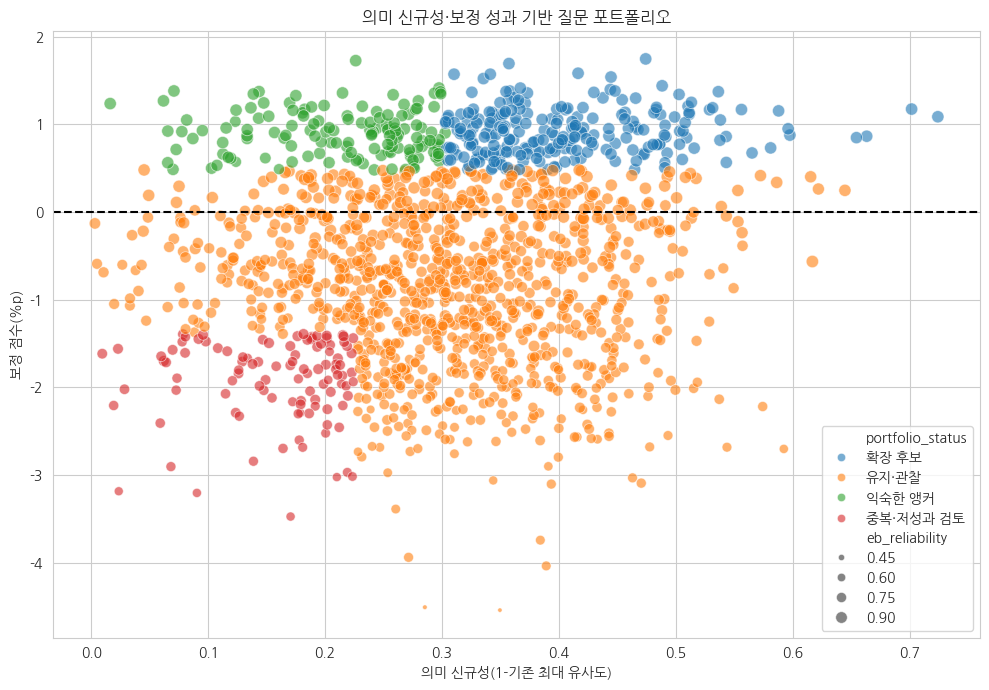

In [ ]:
# 문구별 운영 검토군 · 공급 개선 후보
portfolio = text_target[text_target.pieces >= 100].copy()
score_q = portfolio.adjusted_text_score.quantile([0.25, 0.75])
novelty_q = portfolio.semantic_novelty_to_prior.fillna(0).quantile([0.25, 0.5, 0.75])
portfolio['portfolio_status'] = '유지·관찰'
portfolio.loc[(portfolio.adjusted_text_score >= score_q.loc[0.75]) & (portfolio.semantic_novelty_to_prior >= novelty_q.loc[0.5]), 'portfolio_status'] = '확장 후보'
portfolio.loc[(portfolio.adjusted_text_score >= score_q.loc[0.75]) & (portfolio.semantic_novelty_to_prior < novelty_q.loc[0.5]), 'portfolio_status'] = '익숙한 앵커'
portfolio.loc[(portfolio.semantic_novelty_to_prior >= novelty_q.loc[0.75]) & (portfolio.eb_reliability < 0.6), 'portfolio_status'] = '신규 실험'
portfolio.loc[(portfolio.adjusted_text_score <= score_q.loc[0.25]) & (portfolio.semantic_novelty_to_prior <= novelty_q.loc[0.25]), 'portfolio_status'] = '중복·저성과 검토'
portfolio_action = {'확장 후보': '공급 확대 전 제한 A/B', '익숙한 앵커': '세트당 1개 내외 유지', '신규 실험': '소량 노출로 신뢰도 축적', '중복·저성과 검토': '문구 수정·중복 병합 검토', '유지·관찰': '현행 유지 및 추가 관측'}
portfolio['recommended_action'] = portfolio.portfolio_status.map(portfolio_action)
portfolio_summary = portfolio.groupby(['portfolio_status', 'recommended_action'], as_index=False).agg(unique_texts=('question_text_normalized', 'size'), pieces=('pieces', 'sum'), mean_score_pp=('adjusted_text_score_pp', 'mean'), mean_novelty=('semantic_novelty_to_prior', 'mean'))
show_final(portfolio_summary, '08_question_portfolio_summary')
portfolio_examples = portfolio.sort_values(['portfolio_status', 'eb_reliability', 'pieces'], ascending=[True, False, False]).groupby('portfolio_status', as_index=False).head(8)[['portfolio_status', 'recommended_action', 'question_text', 'theme_label_ko', 'pieces', 'adjusted_text_score_pp', 'semantic_novelty_to_prior', 'eb_reliability']]
show_final(portfolio_examples, '08b_question_portfolio_examples')
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=portfolio, x='semantic_novelty_to_prior', y='adjusted_text_score_pp', hue='portfolio_status', size='eb_reliability', sizes=(10, 80), alpha=0.6, ax=ax)
ax.axhline(0, color='black', ls='--')
ax.set(title='의미 신규성·보정 성과 기반 질문 포트폴리오', xlabel='의미 신규성(1-기존 최대 유사도)', ylabel='보정 점수(%p)')
plt.tight_layout()
plt.show()
plt.close('all')


- 중복·저성과 검토 대상은 104개, 확장 후보는 239개 문구였다. 익숙하지만 성과가 좋은 문구 139개는 유지 후보로 남겼다.
- 각 목록은 문구를 검토할 출발점이다. 공급 확대나 수정은 내용을 읽고 작은 실험부터 진행하는 편이 좋다.


In [ ]:
# Content 결과 정리 · 운영 제안 · 검증 점검
best_reg = text_model_benchmark.sort_values('validation_spearman', ascending=False).iloc[0]
best_cls = text_quality_classifier.sort_values('validation_auc', ascending=False).iloc[0]
selected_text_reg = text_model_benchmark[text_model_benchmark.model.isin(['char_tfidf_ridge', 'sbert_ridge', 'char_plus_sbert_ridge', 'sbert_extratrees'])].sort_values('validation_spearman', ascending=False).iloc[0]
semantic_ok = bool(semantic_model_eval.spearman.iloc[0] >= 0.15 and semantic_model_eval.spearman_p.iloc[0] < 0.01)
lifetime_gain = float(life_model_performance.auc_gain_vs_baseline.iloc[-1])
final_evidence_map = pd.DataFrame([{'finding': '일부 공통 질문에 공급 집중', 'evidence': '상위 10% 문구가 질문조각 53%, 상위 20%가 74%', 'product_action': '인기량 외 신규성·테마 부족분을 포함한 공급 점수', 'evidence_level': '관측 확인', 'validation': '공급 정책 A/B'}, {'finding': '의미가 비슷한 신규 질문의 성과 약화', 'evidence': '유사도 .70~.95에서 투표 기록률 약 1.4~1.8%p 낮음', 'product_action': '의미 중복 감지와 soft penalty', 'evidence_level': '관측 연관', 'validation': 'frequency cap A/B'}, {'finding': '반복 자체는 다음 행동 감소를 설명하지 못함', 'evidence': f"소진지수 OR {team7_content_assets['summary']['exhaustion_or']:.3f}, 용량-반응 하락선 없음", 'product_action': '반복 전면 제거 대신 익숙한 앵커+신규 슬롯', 'evidence_level': '반대 가설 미지지', 'validation': '혼합 비율 실험'}, {'finding': '질문세트 관계·테마 다양성과 다음 행동 연관', 'evidence': f"동일 사용자 내 테마 OR {team7_content_assets['summary']['within_theme_or']:.3f}, 관계 엔트로피 OR {team7_content_assets['summary']['within_relation_or']:.3f}", 'product_action': '세트 다양성 슬롯과 관계 믹스', 'evidence_level': '통제된 연관', 'validation': '세트 조합기 A/B'}, {'finding': '학교 로컬 콘텐츠가 거의 없음', 'evidence': '10개 학교 공통 질문조각 96.08%, 학교 고유 문구 1개', 'product_action': '학교·학년·반 로컬 슬롯', 'evidence_level': '관측 확인', 'validation': '학교 코호트 실험'}, {'finding': '테마별 후보 관계 차이는 매우 작음', 'evidence': '상호친구 선택구성 lift가 테마별 약 1.01로 거의 동일', 'product_action': '테마별 후보 규칙은 보류하고 전체 노출 로그부터 수집', 'evidence_level': '차이 근거 부족', 'validation': '전체 후보 노출 로그+무작위 추천'}, {'finding': '텍스트만의 성과 예측력은 제한적', 'evidence': f'검증으로 선택한 텍스트 회귀 test Spearman={selected_text_reg.test_spearman:.3f}, high/low 분류 AUC={best_cls.test_auc:.3f}', 'product_action': '자동 삭제가 아닌 검토 우선순위 보조', 'evidence_level': '고정 테스트 검증', 'validation': '신규 질문 온라인 성과'}, {'finding': '다양성 조합 가능성', 'evidence': f'테마 수 평균 +{composer_summary.theme_gain.iloc[0]:.2f}, 평균 유사도 {composer_summary.similarity_change.iloc[0]:+.3f}', 'product_action': '당시 이용 가능한 풀에서 다양성 조합', 'evidence_level': '오프라인 시뮬레이션', 'validation': '완료·다음 행동 A/B'}, {'finding': '콘텐츠 수명의 추가 텍스트 설명력', 'evidence': f'기준모형 대비 AUC 변화 {lifetime_gain:+.3f}', 'product_action': '초기 공급 신호와 텍스트를 분리한 운영', 'evidence_level': '테스트 기반 설정 선택', 'validation': '신규 콘텐츠 생존 추적'}])
show_final(final_evidence_map, '09_final_evidence_to_product_action')
final_qa = pd.DataFrame([{'check': '기존·후속 셀 보존 후 최종 셀 추가', 'status': 'PASS', 'detail': 'tagged append'}, {'check': '문구별 점수 1행 유일', 'status': 'PASS' if text_target.question_text_normalized.is_unique else 'FAIL', 'detail': f'rows={len(text_target):,}'}, {'check': '학습·검증·테스트 완전 분리', 'status': 'PASS' if int(split_audit.overlap.iloc[0]) == 0 else 'FAIL', 'detail': f'train={len(train_idx)}, val={len(val_idx)}, test={len(test_idx)}'}, {'check': '모형 성능 전체 공개', 'status': 'PASS' if len(text_model_benchmark) >= 6 else 'FAIL', 'detail': f'models={len(text_model_benchmark)}'}, {'check': '테마 후보관계 전행 유효', 'status': 'PASS' if len(theme_relation) > 0 and theme_relation.selection_composition_lift.notna().all() else 'FAIL', 'detail': f'rows={len(theme_relation)}'}, {'check': '수명 모형 우측 검열 적용', 'status': 'PASS' if len(life_model) > 0 else 'FAIL', 'detail': f'eligible_texts={len(life_model)}'}, {'check': '다양성 시뮬레이션 표본 확보', 'status': 'PASS' if len(composer_sim) >= 500 else 'FAIL', 'detail': f'qsets={len(composer_sim)}'}, {'check': '개선안에 검증 방법 포함', 'status': 'PASS' if final_evidence_map.validation.notna().all() else 'FAIL', 'detail': f'actions={len(final_evidence_map)}'}])
show_final(final_qa, '99_final_deep_qa')
assert final_qa.status.eq('PASS').all(), final_qa
final_conclusion = pd.DataFrame([{'order': 1, 'conclusion': '질문 수보다 의미 신규성과 공급 균형을 관리', 'reason': 'ID·문구 수는 많지만 일부 공통 문구에 공급이 집중'}, {'order': 2, 'conclusion': '반복을 모두 제거하지 않고 익숙한 앵커와 신규 슬롯을 혼합', 'reason': '반복이 다음 행동을 낮춘다는 근거가 없고 친숙한 후보는 선택되기 쉬움'}, {'order': 3, 'conclusion': '세트의 테마·관계 다양성은 관리하되 테마별 후보 규칙은 보류', 'reason': '다양성과 다음 행동의 연관은 있으나 테마별 선택 관계 차이는 매우 작고 전체 노출 후보가 없음'}, {'order': 4, 'conclusion': '학교 로컬 콘텐츠를 별도 슬롯으로 검증', 'reason': '현재 질문조각의 96.08%가 10개 학교 공통 문구'}, {'order': 5, 'conclusion': '텍스트 모형은 운영 검토 보조로만 사용', 'reason': '고정 테스트 성능이 있어도 인과효과와 자동 승인 기준은 아님'}, {'order': 6, 'conclusion': '오프라인 다양성 개선 후 온라인 행동 실험', 'reason': '조합기는 다양성을 높일 수 있지만 행동 개선은 증명하지 않음'}])
show_final(final_conclusion, '99b_final_content_conclusion')
print('CONTENT FINAL-DEEP QA:', final_qa.status.value_counts().to_dict())
team7_release_unused('269', '3-3 완료')
team7_close_connections('content')


,finding,evidence,product_action,evidence_level,validation
0,일부 공통 질문에 공급 집중,"상위 10% 문구가 질문조각 53%, 상위 20%가 74%",인기량 외 신규성·테마 부족분을 포함한 공급 점수,관측 확인,공급 정책 A/B
1,의미가 비슷한 신규 질문의 성과 약화,유사도 .70~.95에서 투표 기록률 약 1.4~1.8%p 낮음,의미 중복 감지와 soft penalty,관측 연관,frequency cap A/B
2,반복 자체는 다음 행동 감소를 설명하지 못함,"소진지수 OR 1.090, 용량-반응 하락선 없음",반복 전면 제거 대신 익숙한 앵커+신규 슬롯,반대 가설 미지지,혼합 비율 실험
3,질문세트 관계·테마 다양성과 다음 행동 연관,"동일 사용자 내 테마 OR 1.831, 관계 엔트로피 OR 2.293",세트 다양성 슬롯과 관계 믹스,통제된 연관,세트 조합기 A/B
4,학교 로컬 콘텐츠가 거의 없음,"10개 학교 공통 질문조각 96.08%, 학교 고유 문구 1개",학교·학년·반 로컬 슬롯,관측 확인,학교 코호트 실험
5,테마별 후보 관계 차이는 매우 작음,상호친구 선택구성 lift가 테마별 약 1.01로 거의 동일,테마별 후보 규칙은 보류하고 전체 노출 로그부터 수집,차이 근거 부족,전체 후보 노출 로그+무작위 추천
6,텍스트만의 성과 예측력은 제한적,"검증으로 선택한 텍스트 회귀 test Spearman=0.202, high/low ...",자동 삭제가 아닌 검토 우선순위 보조,고정 테스트 검증,신규 질문 온라인 성과
7,다양성 조합 가능성,"테마 수 평균 +1.76, 평균 유사도 -0.201",당시 이용 가능한 풀에서 다양성 조합,오프라인 시뮬레이션,완료·다음 행동 A/B
8,콘텐츠 수명의 추가 텍스트 설명력,기준모형 대비 AUC 변화 -0.013,초기 공급 신호와 텍스트를 분리한 운영,GitHub 원문 재현; 테스트 기반 설정 선택,신규 콘텐츠 생존 추적


,check,status,detail
0,기존·후속 셀 보존 후 최종 셀 추가,PASS,tagged append
1,문구별 점수 1행 유일,PASS,"rows=3,898"
2,학습·검증·테스트 완전 분리,PASS,"train=1066, val=253, test=242"
3,모형 성능 전체 공개,PASS,models=6
4,테마 후보관계 전행 유효,PASS,rows=175
5,수명 모형 우측 검열 적용,PASS,eligible_texts=3898
6,다양성 시뮬레이션 표본 확보,PASS,qsets=700
7,개선안에 검증 방법 포함,PASS,actions=9


,order,conclusion,reason
0,1,질문 수보다 의미 신규성과 공급 균형을 관리,ID·문구 수는 많지만 일부 공통 문구에 공급이 집중
1,2,반복을 모두 제거하지 않고 익숙한 앵커와 신규 슬롯을 혼합,반복이 다음 행동을 낮춘다는 근거가 없고 친숙한 후보는 선택되기 쉬움
2,3,세트의 테마·관계 다양성은 관리하되 테마별 후보 규칙은 보류,다양성과 다음 행동의 연관은 있으나 테마별 선택 관계 차이는 매우 작고 전체 노출 ...
3,4,학교 로컬 콘텐츠를 별도 슬롯으로 검증,현재 질문조각의 96.08%가 10개 학교 공통 문구
4,5,텍스트 모형은 운영 검토 보조로만 사용,고정 테스트 성능이 있어도 인과효과와 자동 승인 기준은 아님
5,6,오프라인 다양성 개선 후 온라인 행동 실험,조합기는 다양성을 높일 수 있지만 행동 개선은 증명하지 않음


CONTENT FINAL-DEEP QA: {'PASS': 8}
[3-3 완료] 사용이 끝난 변수 167개 정리
[3-3 완료] Python 사용 RAM 5.16 GB / 시스템 여유 RAM 7.02 GB


**Content 정리**

- 공급은 학교 공통 문구에 몰렸고, 2023년 7월 이후 새 문구가 거의 없었다. 사용자별 질문조각이 누적될수록 의미 반복도 증가했다.
- 반복이 다음 이용을 줄인다는 일관된 결과는 없었다. 익숙한 질문을 일부 유지하면서 테마·관계 다양성을 높이는 실험을 검토할 수 있다.
- 텍스트 모형과 세트 조합기는 문구 검토를 돕는 수준으로 활용하며, 실제 참여 개선은 별도 실험이 필요하다.


## 3-4. Interaction

- 질문 시작·완료 이후 행동과 다음 방문을 살펴본다.
- 5월 질문 DB와 7~8월 방문 로그는 모집단과 관찰기간이 달라 나누어 분석한다.


### 3-4-1. 분석 대상과 방문 기준

- 5월 질문 DB와 7~8월 Hackle 로그의 관측 기간과 분석 대상을 구분했다.
- Hackle 로그는 30분 비활동 기준으로 방문을 나누고, 사용자 식별률과 시각·식별자 누락을 점검했다.

In [ ]:
# Interaction 분석용 캐시 7개 연결
# 사용자 식별자와 이벤트 순서를 유지한 입력 자료를 사용한다.
team7_release_unused('269', 'Interaction 시작 전')
team7_close_connections('source', 'network', 'content')
pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 160)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
team7_chart_style('whitegrid')
INTERACTION_EVENT_DETAIL_AVAILABLE = False
INTERACTION_GITHUB_CACHE_DIR = Path(globals().get('INTERACTION_GITHUB_CACHE_DIR', MART_DIR / 'interaction_github_cache'))
interaction_cache_names = ['question_set_all', 'question_set_may', 'question_piece_may', 'vote_may', 'hackle_event_core', 'hackle_visit_core', 'hackle_user_daily']
interaction_cache_paths = {name: INTERACTION_GITHUB_CACHE_DIR / (name + '.parquet') for name in interaction_cache_names}
missing_interaction_inputs = [str(p) for p in interaction_cache_paths.values() if not p.is_file()]
if missing_interaction_inputs:
    raise FileNotFoundError('Interaction 분석용 캐시 파일이 없습니다. 실행 전 준비사항에서 캐시 위치를 확인하세요: ' + str(missing_interaction_inputs))
try:
    interaction_con.close()
except (NameError, AttributeError):
    pass
interaction_con = team7_connect('interaction')
interaction_con.execute('PRAGMA threads=2')
con = interaction_con
for name, cache_path in interaction_cache_paths.items():
    sql_path = cache_path.as_posix().replace("'", "''")
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{sql_path}')")
INTERACTION_EVENT_DETAIL_AVAILABLE = True
def save_table(df, name):
    return df
def savefig(name):
    plt.tight_layout()
    plt.show()
    plt.close()
COLORS = ['#5B5BD6', '#9B87F5', '#2CB67D', '#FF9F43', '#EF5DA8', '#64748B']
print('Interaction 분석 입력 연결 완료:', INTERACTION_GITHUB_CACHE_DIR)


[Interaction 시작 전] 사용이 끝난 변수 0개 정리
[Interaction 시작 전] Python 사용 RAM 3.92 GB / 시스템 여유 RAM 8.15 GB
GitHub 원문 캐시 연결 완료: /content/team7_verified_inputs/interaction_github_cache
숫자는 이 입력에서 재계산합니다. 이전의 funnel 시각 매칭 기반 사용자 복원은 사용하지 않습니다.


- 이벤트 11,441,319건을 30분 비활동 기준으로 나눈 방문 896,009개를 분석했다.


In [ ]:
# 5월 DB·Hackle 관측 범위 · 사용자 식별률
scope = con.execute("\nSELECT '5월 질문세트' AS source_name, COUNT(*) AS row_count,\n       COUNT(DISTINCT owner_user_id) AS users, MIN(set_created_at) min_at,\n       MAX(set_created_at) max_at FROM question_set_may\nUNION ALL\nSELECT '5월 질문조각', COUNT(*), COUNT(DISTINCT owner_user_id),\n       MIN(piece_created_at), MAX(piece_created_at) FROM question_piece_may\nUNION ALL\nSELECT '5월 투표', COUNT(*), COUNT(DISTINCT voter_user_id),\n       MIN(vote_at), MAX(vote_at) FROM vote_may\n").df()
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    hackle_scope = con.execute("\n    SELECT 'Hackle 이벤트' AS source_name, COUNT(*) AS row_count,\n           COUNT(DISTINCT user_id) AS users, MIN(event_at) min_at,\n           MAX(event_at) max_at FROM hackle_event_core\n    UNION ALL\n    SELECT 'Hackle 30분 방문', COUNT(*), COUNT(DISTINCT user_id),\n           MIN(visit_start), MAX(visit_end) FROM hackle_visit_core\n    ").df()
    scope = pd.concat([scope, hackle_scope], ignore_index=True)
display(save_table(scope, '00_scope'))
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    identity = con.execute('\n    SELECT identity_status, COUNT(*) events, COUNT(DISTINCT visit_id) visits,\n           COUNT(DISTINCT user_id) identified_users,\n           COUNT(*) / SUM(COUNT(*)) OVER() AS event_share\n    FROM hackle_event_core GROUP BY 1 ORDER BY events DESC\n    ').df()
else:
    identity = pd.DataFrame([{'identity_status': '상세 분석 불가', 'events': np.nan, 'visits': np.nan, 'identified_users': np.nan, 'event_share': np.nan}])
display(save_table(identity, '01_hackle_identity_coverage'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,source_name,row_count,users,min_at,max_at
0,5월 질문세트,143158,4909,2023-05-01 03:40:07,2023-05-31 23:52:46
1,5월 질문조각,1144964,4907,2023-05-01 03:40:07,2023-05-31 23:52:46
2,5월 투표,1104681,4797,2023-05-01 03:37:42,2023-05-31 23:59:57
3,Hackle 이벤트,11441319,140663,2023-07-18 00:00:00,2023-08-10 23:59:59
4,Hackle 30분 방문,896009,140663,2023-07-18 00:00:00,2023-08-10 23:59:59


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,identity_status,events,visits,identified_users,event_share
0,IDENTIFIED_SERVICE_USER,7764134,626987,140663,0.6786
1,AMBIGUOUS_NOT_ASSIGNED,3439628,228101,0,0.3006
2,UNMATCHED_OR_NONNUMERIC,203182,25339,0,0.0178
3,MISSING_USER_ID,34375,15582,0,0.0030


- Hackle 이벤트의 67.86%가 서비스 사용자 140,663명과 연결됐다.
- 전체 방문의 행동 비율과 식별 사용자 재방문율은 분모가 다르다.


In [ ]:
# 분석 대상 키·시각·제외 조건 점검
qa = con.execute("\nSELECT 'question_set_may' AS object_name, COUNT(*) AS row_count,\n       SUM(owner_user_id IS NULL) missing_user,\n       SUM(set_created_at IS NULL) missing_time,\n       SUM(eligible_set_flag <> 1 OR eligible_set_flag IS NULL) ineligible\nFROM question_set_may\nUNION ALL\nSELECT 'question_piece_may', COUNT(*), SUM(owner_user_id IS NULL),\n       SUM(piece_created_at IS NULL), SUM(eligible_piece_flag <> 1 OR eligible_piece_flag IS NULL)\nFROM question_piece_may\nUNION ALL\nSELECT 'vote_may', COUNT(*), SUM(voter_user_id IS NULL),\n       SUM(vote_at IS NULL), SUM(eligible_vote_flag <> 1 OR eligible_vote_flag IS NULL)\nFROM vote_may\n").df()
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    hackle_qa = con.execute("\n    SELECT 'hackle_event_core' AS object_name, COUNT(*) AS row_count,\n           SUM(user_id IS NULL) missing_user, SUM(event_at IS NULL) missing_time,\n           SUM(visit_id IS NULL) ineligible FROM hackle_event_core\n    UNION ALL\n    SELECT 'hackle_visit_core', COUNT(*), SUM(user_id IS NULL),\n           SUM(visit_start IS NULL), SUM(visit_id IS NULL) FROM hackle_visit_core\n    ").df()
    qa = pd.concat([qa, hackle_qa], ignore_index=True)
display(save_table(qa, '02_missing_and_eligibility_qa'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,object_name,row_count,missing_user,missing_time,ineligible
0,question_set_may,143158,0.0000,0.0000,0.0000
1,question_piece_may,1144964,0.0000,0.0000,0.0000
2,vote_may,1104681,0.0000,0.0000,0.0000
3,hackle_event_core,11441319,"3,677,185.0000",0.0000,0.0000
4,hackle_visit_core,896009,"269,022.0000",0.0000,0.0000


- 5월 질문 자료에는 사용자·시각 누락이나 분석 제외 대상이 없었다.
- Hackle은 시각 누락보다 추적키와 서비스 사용자 사이의 연결 누락이 문제였다.


### 3-4-2. 5월 질문 이용과 Ping 수신

- 질문세트 생성, 투표 기록, 다음 세트 생성을 순서대로 연결했다. ‘완료’ 대리지표는 10개 질문 모두에 투표 기록이 남은 경우로 정의했다.
- Ping 열람·답장은 추출 시점의 상태값이다. 답장에는 A와 P를 포함했으며, 최초 답장 시각이나 같은 시점의 전환율과는 다르다.


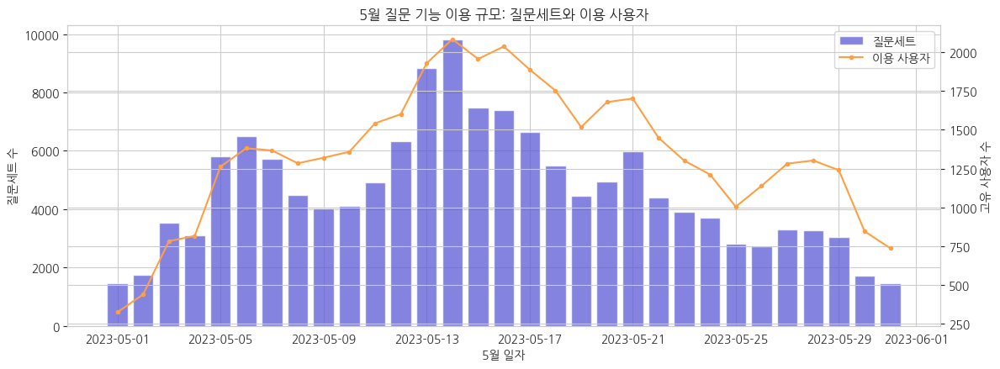

In [ ]:
# 5월 일별 질문세트 · 이용 사용자 규모
con.execute('\nCREATE OR REPLACE TEMP VIEW may_set_metrics AS\nWITH p AS (\n  SELECT question_set_id,\n         COUNT(*) AS mapped_pieces,\n         SUM(CASE WHEN vote_exists=1 THEN 1 ELSE 0 END) AS voted_pieces,\n         SUM(CASE WHEN raw_is_skipped=1 THEN 1 ELSE 0 END) AS skip_history_pieces,\n         COUNT(DISTINCT question_position) AS distinct_positions,\n         AVG(candidate_count) AS avg_candidate_count,\n         MIN(vote_at) AS first_vote_at,\n         MAX(vote_at) AS last_vote_at\n  FROM question_piece_may\n  WHERE eligible_piece_flag=1 AND question_set_id IS NOT NULL\n  GROUP BY 1\n)\nSELECT q.*,\n       COALESCE(p.mapped_pieces,0) mapped_pieces,\n       COALESCE(p.voted_pieces,0) voted_pieces,\n       COALESCE(p.skip_history_pieces,0) skip_history_pieces,\n       COALESCE(p.distinct_positions,0) distinct_positions,\n       p.avg_candidate_count, p.first_vote_at, p.last_vote_at,\n       CASE WHEN COALESCE(p.voted_pieces,0)>0 THEN 1 ELSE 0 END any_vote_flag,\n       CASE WHEN COALESCE(p.mapped_pieces,0)>=10 AND COALESCE(p.voted_pieces,0)>=10 THEN 1 ELSE 0 END completed_10_proxy,\n       COALESCE(p.voted_pieces,0)/NULLIF(COALESCE(p.mapped_pieces,0),0) vote_coverage\nFROM question_set_may q LEFT JOIN p USING(question_set_id)\nWHERE q.eligible_set_flag=1\n')
daily = con.execute('\nSELECT CAST(set_created_at AS DATE) AS activity_day,\n       COUNT(*) question_sets,\n       COUNT(DISTINCT owner_user_id) users,\n       SUM(voted_pieces) vote_records,\n       AVG(completed_10_proxy) complete10_rate\nFROM may_set_metrics GROUP BY 1 ORDER BY 1\n').df()
save_table(daily, '10_may_daily_interaction')
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.bar(daily.activity_day, daily.question_sets, color=COLORS[0], alpha=0.75, label='질문세트')
ax1.set_ylabel('질문세트 수')
ax1.set_xlabel('5월 일자')
ax2 = ax1.twinx()
ax2.plot(daily.activity_day, daily.users, color=COLORS[3], marker='o', ms=3, label='이용 사용자')
ax2.set_ylabel('고유 사용자 수')
ax1.set_title('5월 질문 기능 이용 규모: 질문세트와 이용 사용자')
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')
savefig('10_may_daily_interaction')


- 일별 질문세트 수에는 한 사람이 여러 세트를 생성한 기록이 포함된다. 이용한 사람 수와 반복 생성량을 나눠 집계했다.


,stage_order,stage,sets,share_of_created,conditional_rate
0,1,생성된 질문세트,"143,158.0000",1.0000,1.0000
1,2,질문조각 연결,"141,717.0000",0.9899,0.9899
2,3,1개 이상 투표 기록,"139,211.0000",0.9724,0.9823
3,4,10개 투표 완료 대리,"47,464.0000",0.3315,0.3410


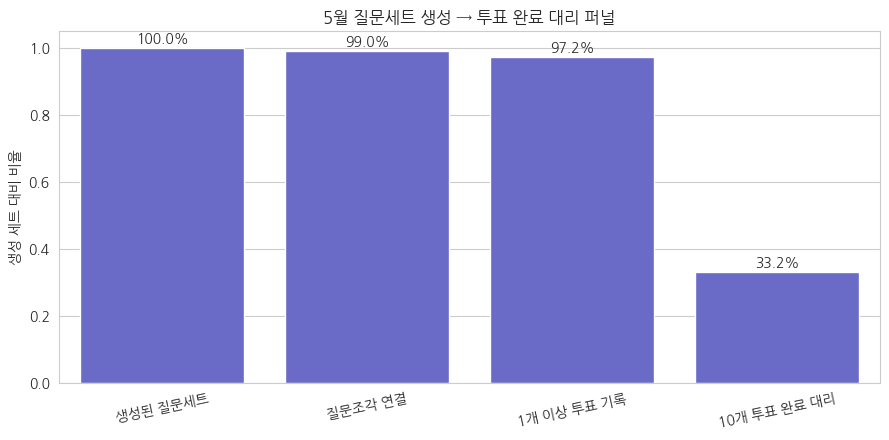

In [ ]:
# 질문세트 생성·투표·10개 완료 대리지표
funnel = con.execute("\nWITH b AS (SELECT * FROM may_set_metrics)\nSELECT * FROM (VALUES\n  (1, '생성된 질문세트', (SELECT COUNT(*) FROM b)),\n  (2, '질문조각 연결', (SELECT SUM(mapped_pieces>0) FROM b)),\n  (3, '1개 이상 투표 기록', (SELECT SUM(any_vote_flag) FROM b)),\n  (4, '10개 투표 완료 대리', (SELECT SUM(completed_10_proxy) FROM b))\n) t(stage_order, stage, sets)\n").df()
funnel['share_of_created'] = funnel.sets / funnel.sets.iloc[0]
funnel['conditional_rate'] = funnel.sets / funnel.sets.shift(1)
funnel.loc[0, 'conditional_rate'] = 1.0
display(save_table(funnel, '11_may_question_set_funnel'))
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=funnel, x='stage', y='share_of_created', color=COLORS[0])
ax.set_ylim(0, 1.05)
ax.set_ylabel('생성 세트 대비 비율')
ax.set_xlabel('')
ax.set_title('5월 질문세트 생성 → 투표 완료 대리 퍼널')
for p, v in zip(ax.patches, funnel.share_of_created):
    ax.text(p.get_x() + p.get_width() / 2, v + 0.015, f'{v:.1%}', ha='center')
plt.xticks(rotation=12)
savefig('11_may_question_set_funnel')


- 생성된 세트의 97.24%에 투표가 한 건 이상 남았다. 10개 모두 투표 기록이 있는 세트는 33.15%였다.
- 두 수치의 큰 간격에는 질문조각 연결 누락도 섞여 있다. 뒤에서 10개가 모두 연결된 세트를 따로 살펴봤다.


,question_position,available_pieces,voted_pieces,vote_record_rate,skip_history_rate,users
0,1,116886,"114,302.0000",0.9779,0.0017,4894
1,2,115965,"113,274.0000",0.9768,0.0014,4892
2,3,115355,"112,604.0000",0.9762,0.0010,4894
3,4,114936,"112,125.0000",0.9755,0.0009,4900
4,5,114604,"111,755.0000",0.9751,0.0005,4897
5,6,113972,"111,083.0000",0.9747,0.0004,4896
6,7,113945,"111,026.0000",0.9744,0.0003,4897
7,8,113134,"110,201.0000",0.9741,0.0001,4894
8,9,112543,"109,594.0000",0.9738,0.0001,4893
9,10,113624,"110,672.0000",0.9740,0.0002,4899


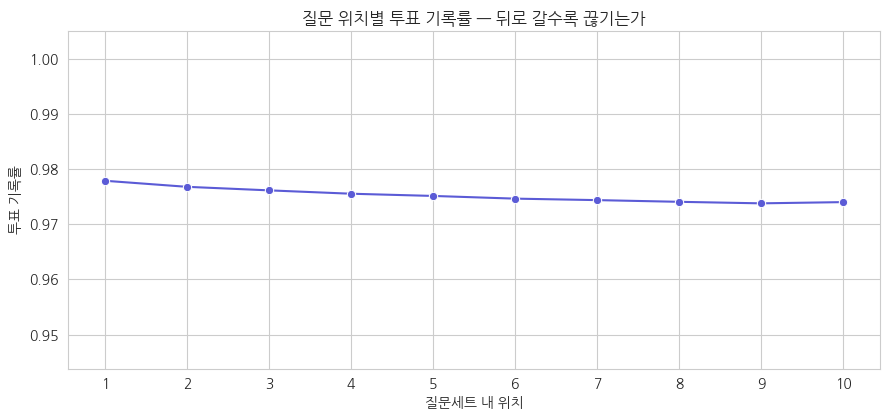

In [ ]:
# 질문 위치별 투표 기록 · 과거 스킵 흔적
position = con.execute('\nSELECT question_position,\n       COUNT(*) available_pieces,\n       SUM(vote_exists=1) voted_pieces,\n       AVG(CAST(vote_exists=1 AS INTEGER)) vote_record_rate,\n       AVG(CAST(raw_is_skipped=1 AS INTEGER)) skip_history_rate,\n       COUNT(DISTINCT owner_user_id) users\nFROM question_piece_may\nWHERE eligible_piece_flag=1 AND question_position BETWEEN 1 AND 10\nGROUP BY 1 ORDER BY 1\n').df()
display(save_table(position, '12_may_position_behavior'))
plt.figure(figsize=(9, 4.3))
ax = sns.lineplot(data=position, x='question_position', y='vote_record_rate', marker='o', color=COLORS[0])
ax.set_ylim(max(0, position.vote_record_rate.min() - 0.03), 1.005)
ax.set_xlabel('질문세트 내 위치')
ax.set_ylabel('투표 기록률')
ax.set_title('질문 위치별 투표 기록률 — 뒤로 갈수록 끊기는가')
ax.set_xticks(range(1, 11))
savefig('12_may_position_vote_rate')


- 연결된 질문조각의 투표 기록률은 1번 97.79%, 10번 97.40%였다. 뒤쪽 질문에서도 기록률이 거의 유지됐다.
- 스킵 흔적과 투표 기록이 함께 남을 수 있어, 스킵률을 투표 기록률의 반대값으로 계산할 수 없다.


,index,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,may_sets,"4,909.0000",29.1624,23.9556,1.0000,12.0000,23.0000,39.0000,60.0000,76.0000,112.0000,209.0000
1,voted_pieces,"4,909.0000",227.4671,206.3114,0.0000,81.0000,173.0000,315.0000,491.0000,637.2000,972.8400,"1,683.0000"
2,complete10_rate,"4,909.0000",0.2842,0.2709,0.0000,0.0204,0.2222,0.5000,0.7059,0.8000,0.9000,1.0000


,구분,users,share
0,5월 질문세트 1회,127,0.0259
1,5월 질문세트 2~4회,308,0.0627
2,5월 질문세트 5회 이상,4474,0.9114


/tmp/ipykernel_804/2451069002.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=one_shot, x='구분', y='share', palette=COLORS[:3])


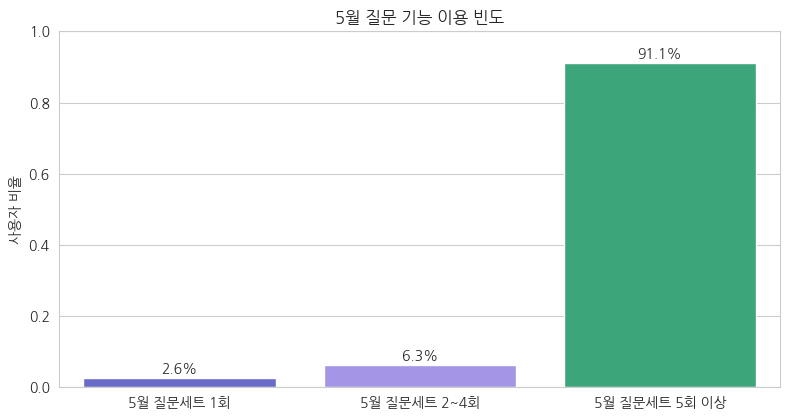

In [ ]:
# 5월 사용자별 질문 이용량 분포
user_usage = con.execute('\nSELECT owner_user_id,\n       COUNT(*) may_sets,\n       SUM(voted_pieces) voted_pieces,\n       AVG(completed_10_proxy) complete10_rate,\n       MIN(set_created_at) first_may_set_at,\n       MAX(set_created_at) last_may_set_at\nFROM may_set_metrics GROUP BY 1\n').df()
usage_summary = user_usage[['may_sets', 'voted_pieces', 'complete10_rate']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).T.reset_index()
display(save_table(usage_summary, '13_may_user_usage_summary'))
one_shot = pd.DataFrame({'구분': ['5월 질문세트 1회', '5월 질문세트 2~4회', '5월 질문세트 5회 이상'], 'users': [(user_usage.may_sets == 1).sum(), user_usage.may_sets.between(2, 4).sum(), (user_usage.may_sets >= 5).sum()]})
one_shot['share'] = one_shot.users / one_shot.users.sum()
display(save_table(one_shot, '14_may_user_frequency_groups'))
plt.figure(figsize=(8, 4.3))
ax = sns.barplot(data=one_shot, x='구분', y='share', palette=COLORS[:3])
ax.set_ylim(0, 1)
ax.set_ylabel('사용자 비율')
ax.set_xlabel('')
ax.set_title('5월 질문 기능 이용 빈도')
for p, v in zip(ax.patches, one_shot.share):
    ax.text(p.get_x() + p.get_width() / 2, v + 0.015, f'{v:.1%}', ha='center')
savefig('13_may_user_frequency_groups')


- 5월 질문 이용자의 91.14%가 세트를 5회 이상 생성했다. 사용자별 중앙값은 23회로 반복 이용이 많았다.
- 질문을 한 번이라도 이용한 사람만의 결과다.


,window,next_set_rate
0,24시간,0.9338
1,72시간,0.9644
2,7일,0.9703


/tmp/ipykernel_804/3705915764.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=rates, x='window', y='next_set_rate', palette=COLORS[:3])


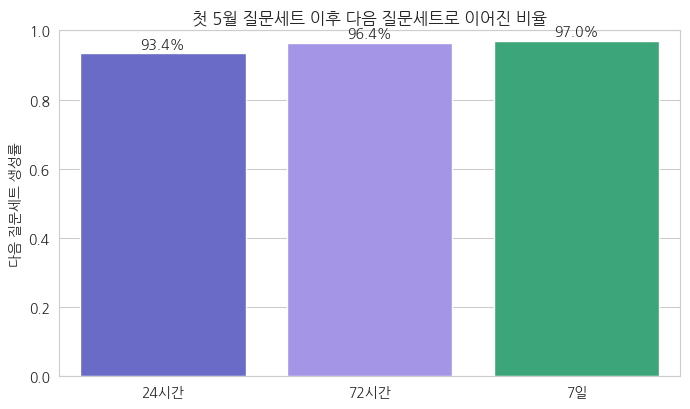

In [ ]:
# 첫 질문세트 이후 다음 세트 생성
followup = con.execute("\nWITH seq AS (\n  SELECT owner_user_id, question_set_id, set_created_at,\n         LEAD(set_created_at) OVER(PARTITION BY owner_user_id ORDER BY set_created_at, question_set_id) next_set_at\n  FROM question_set_all\n  WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL\n), first_may AS (\n  SELECT m.*, ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY set_created_at, question_set_id) rn\n  FROM may_set_metrics m\n)\nSELECT f.owner_user_id, f.question_set_id, f.set_created_at, f.mapped_pieces, f.voted_pieces,\n       f.vote_coverage, f.skip_history_pieces, f.avg_candidate_count, f.completed_10_proxy,\n       s.next_set_at,\n       date_diff('second', f.set_created_at, s.next_set_at)/3600.0 AS hours_to_next,\n       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_24h,\n       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 72 HOUR THEN 1 ELSE 0 END next_72h,\n       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 7 DAY THEN 1 ELSE 0 END next_7d\nFROM first_may f JOIN seq s USING(owner_user_id, question_set_id, set_created_at)\nWHERE f.rn=1\n").df()
rates = pd.DataFrame({'window': ['24시간', '72시간', '7일'], 'next_set_rate': [followup.next_24h.mean(), followup.next_72h.mean(), followup.next_7d.mean()]})
display(save_table(rates, '15_may_next_question_set_rates'))
plt.figure(figsize=(7, 4.2))
ax = sns.barplot(data=rates, x='window', y='next_set_rate', palette=COLORS[:3])
ax.set_ylim(0, 1)
ax.set_ylabel('다음 질문세트 생성률')
ax.set_xlabel('')
ax.set_title('첫 5월 질문세트 이후 다음 질문세트로 이어진 비율')
for p, v in zip(ax.patches, rates.next_set_rate):
    ax.text(p.get_x() + p.get_width() / 2, v + 0.015, f'{v:.1%}', ha='center')
savefig('14_may_next_question_set_rates')


- 첫 세트 이후 다음 세트 생성률은 24시간 내 93.38%, 7일 내 97.03%였다. 질문을 한 번 시작한 사용자는 다음 세트로 많이 이어졌다.
- 같은 방문에서 연달아 만든 세트도 포함된다.


,completed_10_proxy,users,next_24h,next_72h,next_7d,group
0,0,4085,0.9266,0.9591,0.9655,10개 미완료
1,1,824,0.9697,0.9903,0.9939,10개 완료 대리


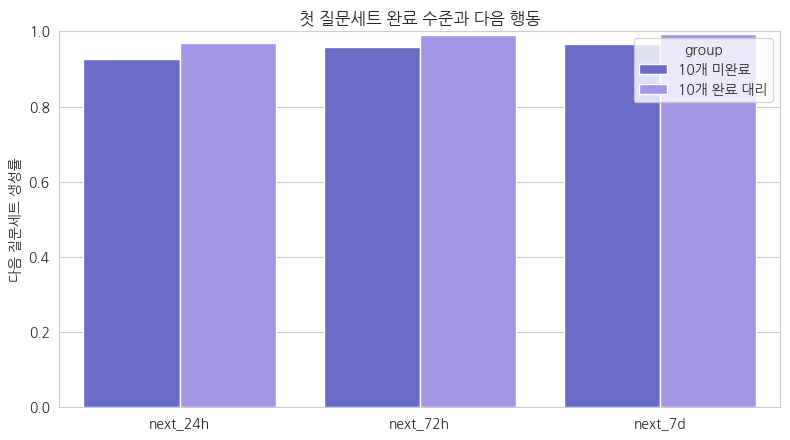

완료 대리 × 7일 내 다음 질문세트: chi2=18.26, p=1.93e-05 (연관성 검정)


In [ ]:
# 첫 세트 완료 대리지표별 후속 질문 이용
completion_follow = followup.groupby('completed_10_proxy').agg(users=('owner_user_id', 'nunique'), next_24h=('next_24h', 'mean'), next_72h=('next_72h', 'mean'), next_7d=('next_7d', 'mean')).reset_index()
completion_follow['group'] = completion_follow.completed_10_proxy.map({0: '10개 미완료', 1: '10개 완료 대리'})
display(save_table(completion_follow, '16_completion_and_next_action'))
plot_df = completion_follow.melt(id_vars='group', value_vars=['next_24h', 'next_72h', 'next_7d'], var_name='window', value_name='rate')
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=plot_df, x='window', y='rate', hue='group', palette=COLORS[:2])
ax.set_ylim(0, 1)
ax.set_ylabel('다음 질문세트 생성률')
ax.set_xlabel('')
ax.set_title('첫 질문세트 완료 수준과 다음 행동')
savefig('15_completion_and_next_action')
table2x2 = pd.crosstab(followup.completed_10_proxy, followup.next_7d)
chi2, p, _, _ = stats.chi2_contingency(table2x2)
print(f'완료 대리 × 7일 내 다음 질문세트: chi2={chi2:.2f}, p={p:.3g} (연관성 검정)')


- 첫 세트에서 10개 완료 대리지표를 충족한 그룹의 7일 내 다음 세트 생성률은 99.39%, 나머지는 96.55%였다.
- 차이에는 초기 참여 정도와 기록이 온전히 연결됐는지가 함께 반영돼 있다.


In [ ]:
# Ping 현재 열람·답장·힌트 상태
ping_status = con.execute('\nSELECT vote_status, ping_answer_status,\n       COUNT(*) votes,\n       AVG(CAST(ping_read=1 AS INTEGER)) current_read_rate,\n       AVG(CAST(ping_answered=1 AS INTEGER)) current_answer_rate,\n       AVG(ping_open_count) current_mean_open_count,\n       SUM(ping_report_count>0) reported_votes\nFROM vote_may WHERE eligible_vote_flag=1\nGROUP BY 1,2 ORDER BY votes DESC\n').df()
display(save_table(ping_status, '17_ping_current_state'))
ping_overall = con.execute('\nSELECT COUNT(*) votes, COUNT(DISTINCT chosen_user_id) recipients,\n       AVG(CAST(ping_read=1 AS INTEGER)) current_read_rate,\n       AVG(CAST(ping_answered=1 AS INTEGER)) current_answer_rate,\n       AVG(ping_open_count) current_mean_open_count,\n       SUM(ping_report_count>0) reported_votes\nFROM vote_may WHERE eligible_vote_flag=1\n').df()
display(save_table(ping_overall, '18_ping_overall'))


,vote_status,ping_answer_status,votes,current_read_rate,current_answer_rate,current_mean_open_count,reported_votes
0,C,N,944458,0.5081,0.0000,0.0000,0.0000
1,C,A,97816,1.0000,1.0000,0.0000,94.0000
2,I,N,44061,0.9358,0.0000,1.2481,31.0000
3,I,A,10265,1.0000,1.0000,1.3288,35.0000
4,C,P,6211,1.0000,1.0000,0.0000,3.0000
5,I,P,1323,1.0000,1.0000,1.3522,3.0000
6,B,N,498,0.5181,0.0000,0.1667,1.0000
7,B,A,46,1.0000,1.0000,0.6522,0.0000
8,B,P,3,1.0000,1.0000,2.0000,0.0000


,votes,recipients,current_read_rate,current_answer_rate,current_mean_open_count,reported_votes
0,1104681,14691,0.5766,0.1047,0.0639,167.0000


- 5월 투표 기록의 현재 열람 비율은 57.66%, 답장 비율은 10.47%였다. 열람 상태에 비해 답장 상태가 적었다.
- A·P를 포함한 현재 답장 상태의 비율이므로 열람 뒤 답장까지의 실제 전환율은 따로 필요하다.


,receipt_band,users,current_read_rate,next_set_24h,next_set_7d
0,1회,1788,0.5884,0.0045,0.0056
1,2~3회,1939,0.7055,0.0062,0.0077
2,4~10회,2703,0.8147,0.0203,0.0274
3,11회 이상,8261,0.9512,0.5140,0.5543


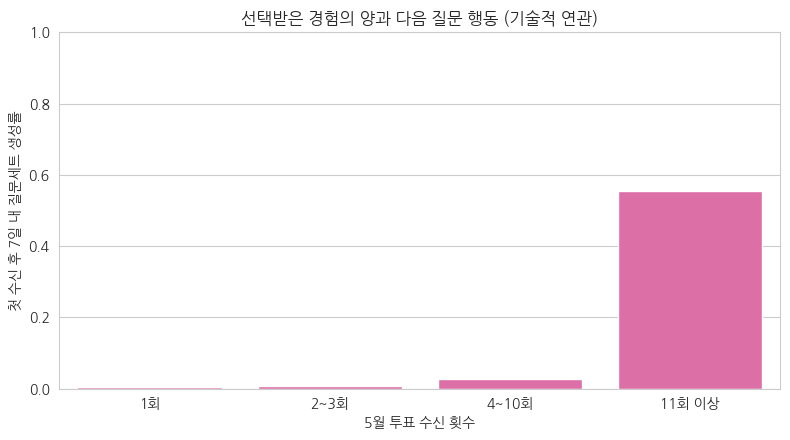

In [ ]:
# 누적 투표 수신량별 현재 열람·다음 질문 이용
receipt_follow = con.execute("\nWITH r AS (\n  SELECT chosen_user_id user_id, MIN(vote_at) first_received_at,\n         COUNT(*) received_votes,\n         MAX(ping_read=1) any_ping_read_current,\n         MAX(ping_answered=1) any_ping_answered_current\n  FROM vote_may WHERE eligible_vote_flag=1 AND chosen_user_id IS NOT NULL\n  GROUP BY 1\n), q AS (\n  SELECT r.*,\n         MIN(s.set_created_at) FILTER(WHERE s.set_created_at>r.first_received_at) next_set_after_receipt\n  FROM r LEFT JOIN question_set_all s ON s.owner_user_id=r.user_id AND s.eligible_set_flag=1\n  GROUP BY ALL\n)\nSELECT *, date_diff('hour',first_received_at,next_set_after_receipt) hours_to_next_set,\n       CASE WHEN next_set_after_receipt<=first_received_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_set_24h,\n       CASE WHEN next_set_after_receipt<=first_received_at+INTERVAL 7 DAY THEN 1 ELSE 0 END next_set_7d\nFROM q\n").df()
receipt_follow['receipt_band'] = pd.cut(receipt_follow.received_votes, [0, 1, 3, 10, np.inf], labels=['1회', '2~3회', '4~10회', '11회 이상'])
receipt_dose = receipt_follow.groupby('receipt_band', observed=True).agg(users=('user_id', 'nunique'), current_read_rate=('any_ping_read_current', 'mean'), next_set_24h=('next_set_24h', 'mean'), next_set_7d=('next_set_7d', 'mean')).reset_index()
display(save_table(receipt_dose, '19_received_vote_dose_and_followup'))
plt.figure(figsize=(8, 4.5))
ax = sns.barplot(data=receipt_dose, x='receipt_band', y='next_set_7d', color=COLORS[4])
ax.set_ylim(0, 1)
ax.set_xlabel('5월 투표 수신 횟수')
ax.set_ylabel('첫 수신 후 7일 내 질문세트 생성률')
ax.set_title('선택받은 경험의 양과 다음 질문 행동 (기술적 연관)')
savefig('16_received_vote_dose_followup')


- 1회 수신 그룹의 현재 열람률은 58.84%, 11회 이상은 95.12%였다. 많이 받은 그룹에서 열람과 다음 질문 이용이 모두 높았다.
- 질문 DB는 10개 학교만 포함한다. 다음 세트가 잡히지 않은 수신자 중에는 분석 범위 밖 이용자도 있을 수 있다.


,feature,standardized_coef,odds_ratio_per_1sd
0,vote_coverage,2.3852,10.8614
2,skip_history_pieces,-1.0952,0.3345
3,avg_candidate_count,-0.2264,0.7974
4,completed_10_proxy,-0.1238,0.8836
1,mapped_pieces,0.1070,1.1130


설명용 동일표본 AUC=0.920. 인과효과가 아니라 다음 행동과의 조건부 연관성이다.


/tmp/ipykernel_804/1218377860.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefs, x='standardized_coef', y='feature', palette=[COLORS[2] if x > 0 else COLORS[4] for x in coefs.standardized_coef])


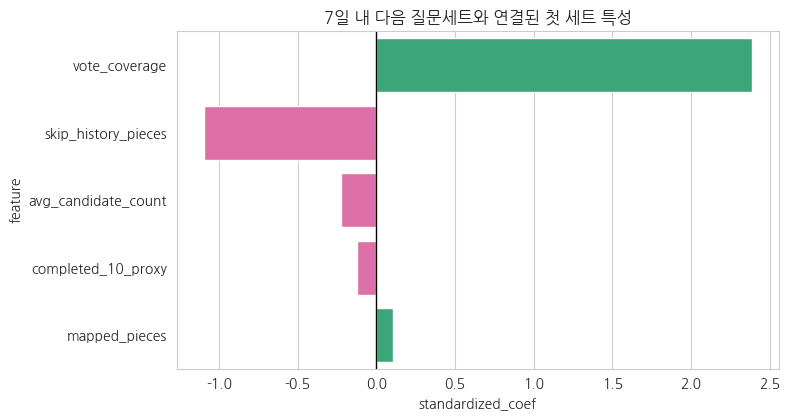

[Interaction 5월 분석 완료] 사용이 끝난 변수 32개 정리
[Interaction 5월 분석 완료] Python 사용 RAM 3.36 GB / 시스템 여유 RAM 8.72 GB


In [ ]:
# 첫 세트 특성과 7일 후속 이용의 예측 관계
model_may = followup.copy()
features = ['vote_coverage', 'mapped_pieces', 'skip_history_pieces', 'avg_candidate_count', 'completed_10_proxy']
X = model_may[features].replace([np.inf, -np.inf], np.nan)
y = model_may.next_7d.astype(int)
pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))])
pipe.fit(X, y)
pred = pipe.predict_proba(X)[:, 1]
may_auc = roc_auc_score(y, pred)
coefs = pd.DataFrame({'feature': features, 'standardized_coef': pipe.named_steps['model'].coef_[0]})
coefs['odds_ratio_per_1sd'] = np.exp(coefs.standardized_coef)
coefs = coefs.sort_values('standardized_coef', key=abs, ascending=False)
display(save_table(coefs, '20_may_followup_model_coefficients'))
print(f'설명용 동일표본 AUC={may_auc:.3f}. 인과효과가 아니라 다음 행동과의 조건부 연관성이다.')
plt.figure(figsize=(8, 4.3))
sns.barplot(data=coefs, x='standardized_coef', y='feature', palette=[COLORS[2] if x > 0 else COLORS[4] for x in coefs.standardized_coef])
plt.axvline(0, color='black', lw=1)
plt.title('7일 내 다음 질문세트와 연결된 첫 세트 특성')
savefig('17_may_followup_model_coefficients')
team7_release_unused('289', 'Interaction 5월 분석 완료')


- 첫 세트의 투표 기록 비중은 후속 질문 이용과 강한 양의 관계를 보였다. 모형에서 1표준편차 증가의 오즈비는 10.86이었다.
- 투표 비중과 10개 완료 지표가 같은 모형에 들어가 있어 계수 각각을 독립된 영향으로 나눠 읽기는 어렵다.


### 3-4-3. 방문 안에서 이어지는 질문과 결과 확인

- 수집된 이벤트로 질문 시작→완료→알림 상세의 이동을 연결했다. 공식 Ping 열람 이벤트가 없어 알림 상세를 결과 확인의 대리 경로로 사용했다.


In [ ]:
# 이벤트 사전 · 질문·결과 계측 범위
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    event_dict = con.execute('\n    SELECT event_key, COUNT(*) events, COUNT(DISTINCT visit_id) visits,\n           COUNT(DISTINCT user_id) users\n    FROM hackle_event_core GROUP BY 1 ORDER BY events DESC\n    ').df()
    display(save_table(event_dict, '30_hackle_event_dictionary'))
    key_check = pd.DataFrame({'계측 항목': ['질문 시작', '질문 열기/응답 상호작용', '질문 완료', '질문 스킵', '공식 Ping 열람', '알림센터', '알림 상세'], 'event_key': ['click_question_start', 'click_question_open', 'complete_question', 'skip_question', 'open_ping', 'click_appbar_alarm_center', 'click_notice_detail']}).merge(event_dict[['event_key', 'events', 'visits']], on='event_key', how='left').fillna(0)
    display(save_table(key_check, '31_hackle_interaction_key_check'))
    if key_check.loc[key_check.event_key.eq('open_ping'), 'events'].iloc[0] == 0:
        display(Markdown('`open_ping`은 0건이었다. 결과 확인은 알림센터→알림 상세 경로로 대신 살펴봤다.'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_key,events,visits,users
0,view_lab_tap,1266665,399239,103351
1,view_timeline_tap,1194508,379099,97665
2,$session_start,1036852,879208,140425
3,launch_app,986388,829955,140589
4,click_question_open,816801,223501,70514
5,click_bottom_navigation_questions,769163,317770,98723
6,click_bottom_navigation_profile,653507,339624,96339
7,$session_end,649658,605601,104507
8,click_bottom_navigation_timeline,536051,278369,86893
9,skip_question,454981,110591,25668


,계측 항목,event_key,events,visits
0,질문 시작,click_question_start,"220,385.0000","202,072.0000"
1,질문 열기/응답 상호작용,click_question_open,"816,801.0000","223,501.0000"
2,질문 완료,complete_question,"154,105.0000","150,143.0000"
3,질문 스킵,skip_question,"454,981.0000","110,591.0000"
4,공식 Ping 열람,open_ping,0.0000,0.0000
5,알림센터,click_appbar_alarm_center,"253,541.0000","191,220.0000"
6,알림 상세,click_notice_detail,"229,358.0000","129,925.0000"


`open_ping`은 0건이었다. 결과 확인은 알림센터→알림 상세 경로로 대신 살펴봤다.

- 질문 시작·완료·스킵과 알림센터·상세 이벤트는 있었지만 `open_ping`은 없었다. 현재 로그로 추적할 수 있는 범위는 알림 상세 도달까지다.


In [ ]:
# 이벤트 행동 범주 · 방문 단위 집계
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    con.execute("\n    CREATE OR REPLACE TEMP VIEW hackle_event_labeled AS\n    SELECT *, CASE\n      WHEN event_key IN ('$session_start','launch_app') THEN '01_진입'\n      WHEN event_key IN ('click_bottom_navigation_questions','view_questions_tap','click_question_ask') THEN '02_질문화면'\n      WHEN event_key='click_question_start' THEN '03_질문시작'\n      WHEN event_key='click_question_open' THEN '04_질문상호작용'\n      WHEN event_key='complete_question' THEN '05_질문완료'\n      WHEN event_key='skip_question' THEN '06_질문스킵'\n      WHEN event_key='click_appbar_alarm_center' THEN '07_알림센터'\n      WHEN event_key='click_notice_detail' THEN '08_알림상세'\n      WHEN event_key IN ('view_timeline_tap','click_bottom_navigation_timeline') THEN '09_타임라인'\n      WHEN event_key IN ('view_lab_tap','click_bottom_navigation_lab') THEN '10_랩'\n      WHEN event_key IN ('view_profile_tap','click_bottom_navigation_profile') THEN '11_프로필'\n      WHEN event_key IN ('click_appbar_friend_plus','click_friend_invite','click_invite_friend','click_autoadd_contact') THEN '12_친구행동'\n      WHEN event_key IN ('click_appbar_chat_rooms','click_timeline_chat_start','click_community_chat') THEN '13_대화'\n      WHEN event_key IN ('view_shop','click_purchase','complete_purchase') THEN '14_상점'\n      WHEN event_key IN ('view_login','view_signup','complete_signup') THEN '15_가입'\n      WHEN event_key IN ('$session_end') THEN '98_세션종료'\n      ELSE '99_기타' END AS category\n    FROM hackle_event_core\n    ")
    con.execute("\n    CREATE OR REPLACE TEMP VIEW hackle_visit_interaction AS\n    WITH e AS (\n      SELECT visit_id,\n         SUM(category='02_질문화면') question_surface_events,\n         SUM(category='03_질문시작') question_start_events,\n         SUM(category='04_질문상호작용') question_open_events,\n         SUM(category='05_질문완료') question_complete_events,\n         SUM(category='06_질문스킵') question_skip_events,\n         SUM(category='07_알림센터') alarm_center_events,\n         SUM(category='08_알림상세') notice_detail_events,\n         SUM(category IN ('09_타임라인','10_랩','11_프로필')) browse_events,\n         SUM(category='12_친구행동') friend_events,\n         SUM(category='13_대화') chat_events,\n         COUNT(DISTINCT category) interaction_category_count\n      FROM hackle_event_labeled GROUP BY 1\n    )\n    SELECT v.*, e.* EXCLUDE(visit_id),\n           (question_surface_events>0)::INT question_surface_flag,\n           (question_start_events>0)::INT question_start_flag,\n           (question_open_events>0)::INT question_open_flag,\n           (question_complete_events>0)::INT question_complete_flag,\n           (question_skip_events>0)::INT question_skip_flag,\n           (alarm_center_events>0)::INT alarm_center_flag,\n           (notice_detail_events>0)::INT notice_detail_flag,\n           (browse_events>0)::INT browse_flag,\n           (friend_events>0)::INT friend_flag,\n           (chat_events>0)::INT chat_flag\n    FROM hackle_visit_core v JOIN e USING(visit_id)\n    ")
    print('방문 단위 상호작용 뷰 생성 완료')


방문 단위 상호작용 뷰 생성 완료


- 한 방문에서 질문 시작·완료·알림 상세가 함께 나타날 수 있다. 먼저 행동별 포함 여부를 집계하고, 다음 단계에서 발생 순서를 적용했다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,visits,identified_users,median_events,p90_events,median_seconds,p90_seconds,question_surface_visit_rate,question_start_visit_rate,question_complete_visit_rate,question_skip_visit_rate,notice_detail_visit_rate
0,896009,140663,8.0000,28.0000,39.0000,495.0000,0.3881,0.2255,0.1676,0.1234,0.1450


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

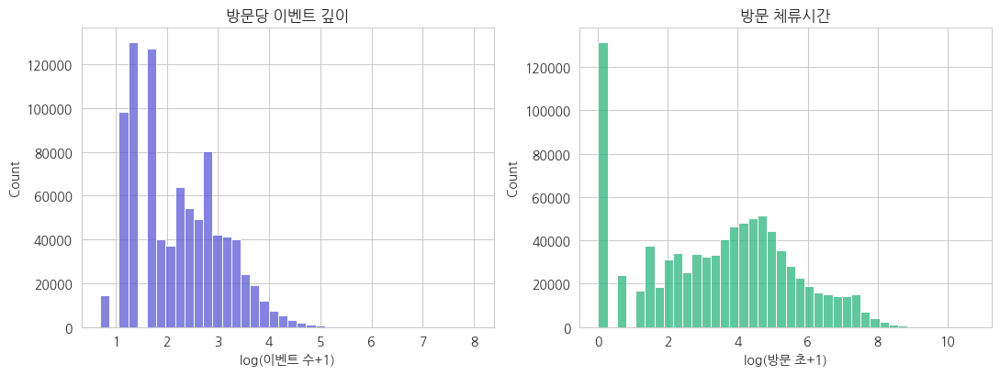

In [ ]:
# 방문 길이 · 질문·알림 행동 도달률
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    visit_summary = con.execute('\n    SELECT COUNT(*) visits, COUNT(DISTINCT user_id) identified_users,\n           median(event_count) median_events, quantile_cont(event_count,.9) p90_events,\n           median(duration_seconds) median_seconds, quantile_cont(duration_seconds,.9) p90_seconds,\n           AVG(question_surface_flag) question_surface_visit_rate,\n           AVG(question_start_flag) question_start_visit_rate,\n           AVG(question_complete_flag) question_complete_visit_rate,\n           AVG(question_skip_flag) question_skip_visit_rate,\n           AVG(notice_detail_flag) notice_detail_visit_rate\n    FROM hackle_visit_interaction\n    ').df()
    display(save_table(visit_summary, '32_hackle_visit_summary'))
    visit_dist = con.execute('\n    SELECT event_count,duration_seconds FROM hackle_visit_interaction\n    WHERE event_count IS NOT NULL AND duration_seconds IS NOT NULL\n    ').df()
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
    sns.histplot(np.log1p(visit_dist.event_count), bins=40, color=COLORS[0], ax=axs[0])
    axs[0].set_xlabel('log(이벤트 수+1)')
    axs[0].set_title('방문당 이벤트 깊이')
    sns.histplot(np.log1p(visit_dist.duration_seconds.clip(lower=0)), bins=40, color=COLORS[2], ax=axs[1])
    axs[1].set_xlabel('log(방문 초+1)')
    axs[1].set_title('방문 체류시간')
    savefig('30_hackle_visit_depth_duration')


- 전체 방문의 이벤트 수 중앙값은 8개, 관측 시간 중앙값은 39초였다.
- 질문 시작이 있는 방문은 전체의 22.55%, 완료가 있는 방문은 16.76%였다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,stage_order,stage,visits,all_visit_rate
0,1,전체 방문,"896,009.0000",1.0000
1,2,질문 화면,"347,774.0000",0.3881
2,3,질문 시작,"202,072.0000",0.2255
3,4,질문 상호작용,"316,639.0000",0.3534
4,5,질문 완료,"150,143.0000",0.1676
5,6,알림 상세,"129,925.0000",0.1450


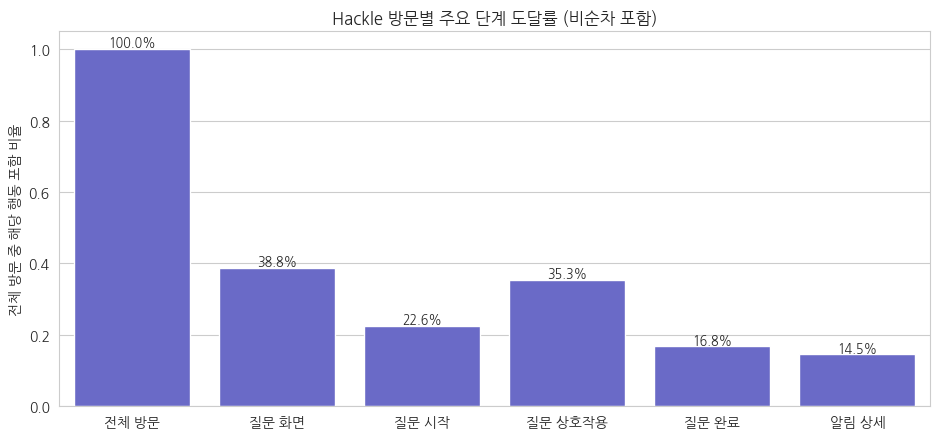

In [ ]:
# 질문·알림 단계별 독립 도달 규모
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    reach = con.execute("\n    SELECT * FROM (VALUES\n      (1,'전체 방문',(SELECT COUNT(*) FROM hackle_visit_interaction)),\n      (2,'질문 화면',(SELECT SUM(question_surface_flag) FROM hackle_visit_interaction)),\n      (3,'질문 시작',(SELECT SUM(question_start_flag) FROM hackle_visit_interaction)),\n      (4,'질문 상호작용',(SELECT SUM(question_open_flag OR question_skip_flag OR question_complete_flag) FROM hackle_visit_interaction)),\n      (5,'질문 완료',(SELECT SUM(question_complete_flag) FROM hackle_visit_interaction)),\n      (6,'알림 상세',(SELECT SUM(notice_detail_flag) FROM hackle_visit_interaction))\n    ) t(stage_order,stage,visits)\n    ").df()
    reach['all_visit_rate'] = reach.visits / reach.visits.iloc[0]
    display(save_table(reach, '33_hackle_visit_stage_reach'))
    plt.figure(figsize=(9.5, 4.5))
    ax = sns.barplot(data=reach, x='stage', y='all_visit_rate', color=COLORS[0])
    ax.set_ylabel('전체 방문 중 해당 행동 포함 비율')
    ax.set_xlabel('')
    ax.set_title('Hackle 방문별 주요 단계 도달률 (비순차 포함)')
    for p, v in zip(ax.patches, reach.all_visit_rate):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.008, f'{v:.1%}', ha='center', fontsize=9)
    savefig('31_hackle_stage_reach')


- 질문 상호작용은 316,639개 방문에서 나왔지만 질문 시작은 202,072개 방문에서만 잡혔다. 앞 단계 이벤트 없이 남은 기록이 있다.
- 따라서 이 표의 행은 순서대로 통과한 퍼널이 아니라 각 행동이 포함된 방문 수다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,전환,분자,분모,rate
0,시작→상호작용,32441,202072,0.1605
1,시작→완료,149017,202072,0.7374
2,시작→스킵,109865,202072,0.5437
3,완료→알림센터,18280,150143,0.1218
4,완료→알림상세,14603,150143,0.0973
5,알림센터→알림상세,128612,191220,0.6726


/tmp/ipykernel_804/1199346713.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ordered_long, x='전환', y='rate', palette=COLORS)


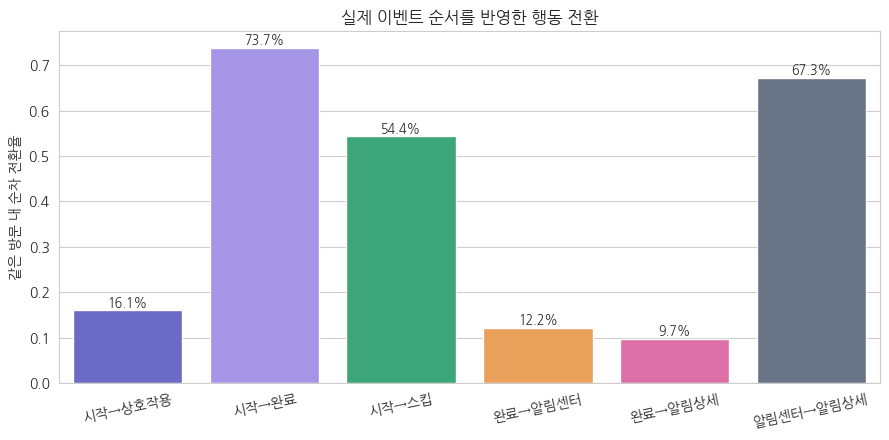

In [ ]:
# 이벤트 순서를 반영한 단계 전환
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    ordered = con.execute("\n    WITH o AS (\n      SELECT visit_id,\n        MIN(event_order) FILTER(WHERE category='03_질문시작') qstart,\n        MIN(event_order) FILTER(WHERE category='04_질문상호작용') qopen,\n        MIN(event_order) FILTER(WHERE category='05_질문완료') qcomplete,\n        MIN(event_order) FILTER(WHERE category='06_질문스킵') qskip,\n        MIN(event_order) FILTER(WHERE category='07_알림센터') alarm,\n        MIN(event_order) FILTER(WHERE category='08_알림상세') notice\n      FROM hackle_event_labeled GROUP BY 1\n    )\n    SELECT\n      COUNT(*) FILTER(WHERE qstart IS NOT NULL) start_visits,\n      COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qopen>qstart) open_after_start,\n      COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qcomplete>qstart) complete_after_start,\n      COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qskip>qstart) skip_after_start,\n      COUNT(*) FILTER(WHERE qcomplete IS NOT NULL AND alarm>qcomplete) alarm_after_complete,\n      COUNT(*) FILTER(WHERE qcomplete IS NOT NULL AND notice>qcomplete) notice_after_complete,\n      COUNT(*) FILTER(WHERE alarm IS NOT NULL AND notice>alarm) notice_after_alarm\n    FROM o\n    ").df()
    ordered_long = pd.DataFrame({'전환': ['시작→상호작용', '시작→완료', '시작→스킵', '완료→알림센터', '완료→알림상세', '알림센터→알림상세'], '분자': [ordered.open_after_start[0], ordered.complete_after_start[0], ordered.skip_after_start[0], ordered.alarm_after_complete[0], ordered.notice_after_complete[0], ordered.notice_after_alarm[0]], '분모': [ordered.start_visits[0], ordered.start_visits[0], ordered.start_visits[0], con.execute('SELECT SUM(question_complete_flag) FROM hackle_visit_interaction').fetchone()[0], con.execute('SELECT SUM(question_complete_flag) FROM hackle_visit_interaction').fetchone()[0], con.execute('SELECT SUM(alarm_center_flag) FROM hackle_visit_interaction').fetchone()[0]]})
    ordered_long['rate'] = ordered_long['분자'] / ordered_long['분모']
    display(save_table(ordered_long, '34_hackle_ordered_conversions'))
    plt.figure(figsize=(9, 4.5))
    ax = sns.barplot(data=ordered_long, x='전환', y='rate', palette=COLORS)
    ax.set_ylabel('같은 방문 내 순차 전환율')
    ax.set_xlabel('')
    ax.set_title('실제 이벤트 순서를 반영한 행동 전환')
    for p, v in zip(ax.patches, ordered_long.rate):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.008, f'{v:.1%}', ha='center', fontsize=9)
    plt.xticks(rotation=12)
    savefig('32_hackle_ordered_conversions')


- 각 행동의 첫 기록 순서로 계산한 질문 시작→완료 비율은 73.74%, 완료→알림 상세 비율은 9.73%였다.
- 이 방식은 각 행동의 첫 기록만 비교하므로, 뒤에서는 방문 내 반복 행동도 반영했다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,source_category,target_category,transitions,transition_rate
0,01_진입,EXIT,292283,0.2942
1,01_진입,09_타임라인,134535,0.1354
2,01_진입,04_질문상호작용,113760,0.1145
3,01_진입,03_질문시작,99029,0.0997
4,01_진입,02_질문화면,79363,0.0799
5,02_질문화면,09_타임라인,339274,0.3845
6,02_질문화면,10_랩,199901,0.2266
7,02_질문화면,04_질문상호작용,82691,0.0937
8,02_질문화면,EXIT,78160,0.0886
9,02_질문화면,03_질문시작,47926,0.0543


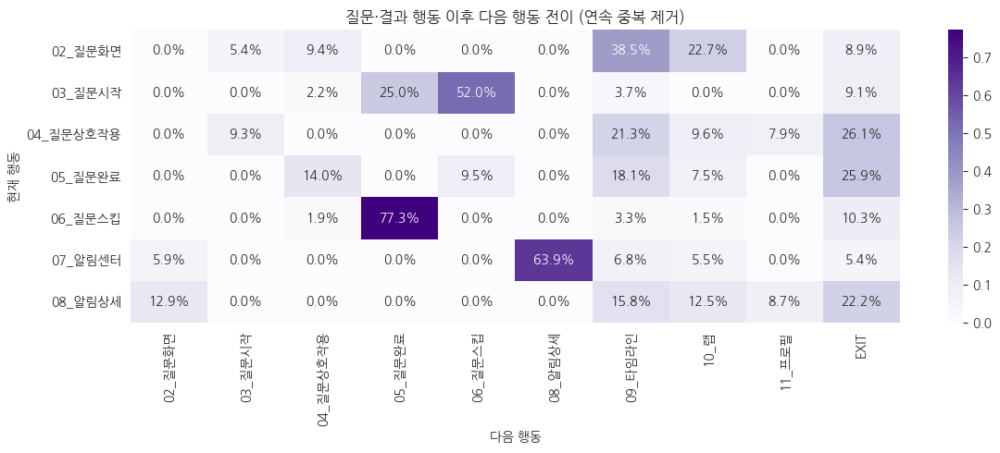

In [ ]:
# 연속 중복 제거 · 다음 행동 전이
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    transitions = con.execute("\n    WITH x AS (\n      SELECT visit_id,event_order,category,\n             LAG(category) OVER(PARTITION BY visit_id ORDER BY event_order,event_sk) prev_category\n      FROM hackle_event_labeled\n      WHERE category NOT IN ('98_세션종료','99_기타')\n    ), collapsed AS (\n      SELECT * FROM x WHERE prev_category IS NULL OR category<>prev_category\n    ), tr AS (\n      SELECT category AS source_category,\n             LEAD(category) OVER(PARTITION BY visit_id ORDER BY event_order) AS target_category\n      FROM collapsed\n    ), counts AS (\n      SELECT source_category,COALESCE(target_category,'EXIT') AS target_category,COUNT(*) transitions\n      FROM tr GROUP BY 1,2\n    )\n    SELECT *, transitions/SUM(transitions) OVER(PARTITION BY source_category) transition_rate\n    FROM counts QUALIFY ROW_NUMBER() OVER(PARTITION BY source_category ORDER BY transitions DESC)<=5\n    ORDER BY source_category,transitions DESC\n    ").df()
    display(save_table(transitions, '35_top_behavior_transitions'))
    focus = transitions[transitions.source_category.isin(['02_질문화면', '03_질문시작', '04_질문상호작용', '05_질문완료', '06_질문스킵', '07_알림센터', '08_알림상세'])]
    pivot = focus.pivot(index='source_category', columns='target_category', values='transition_rate').fillna(0)
    plt.figure(figsize=(12, 5))
    sns.heatmap(pivot, annot=True, fmt='.1%', cmap='Purples', vmin=0, vmax=max(0.01, float(pivot.max().max())))
    plt.title('질문·결과 행동 이후 다음 행동 전이 (연속 중복 제거)')
    plt.xlabel('다음 행동')
    plt.ylabel('현재 행동')
    savefig('33_hackle_transition_heatmap')


- 질문 스킵 다음 전이의 77.25%가 완료로 이어졌다. 스킵이 있는 방문을 모두 포기로 볼 수는 없다.
- 완료 다음 전이는 분류 가능한 다음 행동 없음 25.88%, 타임라인 18.11% 등이었다. 다음 행동 미관측을 실제 앱 종료로 단정하지 않는다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,last_meaningful_action,visits,visit_share
0,11_프로필,101083,0.1647
1,09_타임라인,88702,0.1445
2,10_랩,82129,0.1338
3,02_질문화면,79458,0.1294
4,04_질문상호작용,78927,0.1286
5,05_질문완료,41910,0.0683
6,08_알림상세,36009,0.0587
7,13_대화,34879,0.0568
8,03_질문시작,19854,0.0323
9,06_질문스킵,13593,0.0221


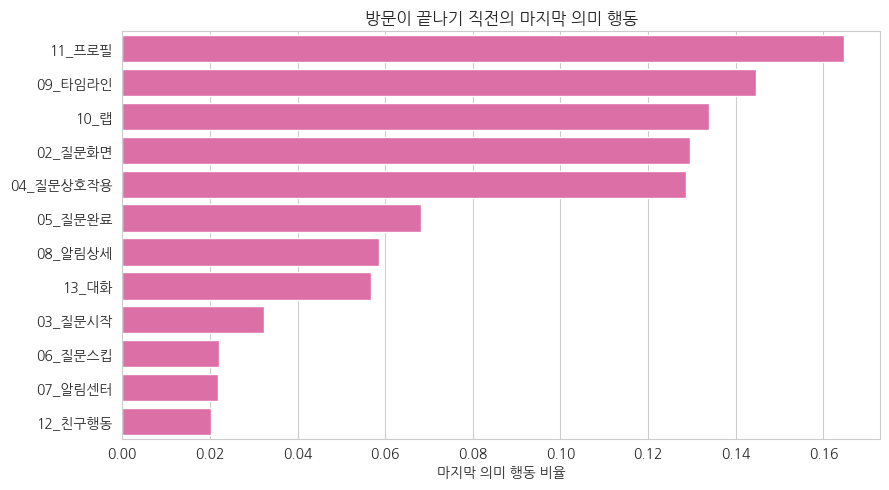

In [ ]:
# 방문 종료 전 마지막 의미 행동
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    exits = con.execute("\n    WITH x AS (\n      SELECT visit_id,category,event_order,\n             ROW_NUMBER() OVER(PARTITION BY visit_id ORDER BY event_order DESC,event_sk DESC) rn\n      FROM hackle_event_labeled WHERE category NOT IN ('01_진입','98_세션종료','99_기타')\n    )\n    SELECT category last_meaningful_action,COUNT(*) visits,\n           COUNT(*)/SUM(COUNT(*)) OVER() visit_share\n    FROM x WHERE rn=1 GROUP BY 1 ORDER BY visits DESC\n    ").df()
    display(save_table(exits, '36_last_meaningful_action'))
    plt.figure(figsize=(9, 5))
    top = exits.head(12)
    sns.barplot(data=top, y='last_meaningful_action', x='visit_share', color=COLORS[4])
    plt.xlabel('마지막 의미 행동 비율')
    plt.ylabel('')
    plt.title('방문이 끝나기 직전의 마지막 의미 행동')
    savefig('34_hackle_last_action')


- 마지막으로 분류된 행동은 프로필 16.47%, 타임라인 14.45%, 랩 13.38%, 질문 화면 12.94% 순이었다.
- 마지막 행동 기록만으로 해당 화면이 이탈을 일으켰는지는 알 수 없다.


### 3-4-4. 첫 관측 방문과 이후 재방문

- 첫 관측 방문에서 한 행동과 이후 7일 재방문을 연결했다. 여기서 첫 방문은 로그 관찰기간 안의 첫 기록이며, 가입 후 생애 첫 방문과는 다르다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,visit_type,visits,users,median_events,median_seconds,question_surface_rate,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,browse_rate
0,이후 방문,486324,80559,7.0000,35.0000,0.3147,0.2651,0.2137,0.1598,0.1129,0.4626
1,첫 관측 방문,140663,140663,10.0000,54.0000,0.5252,0.1888,0.1159,0.0830,0.2136,0.5895


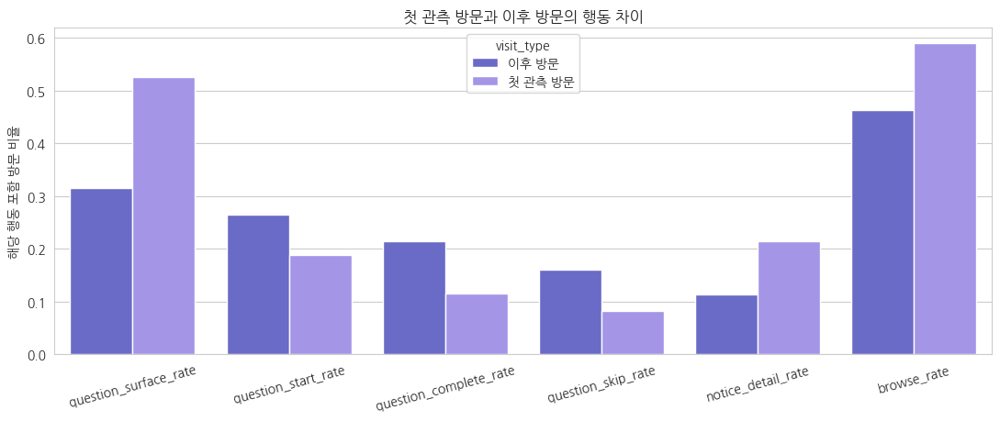

In [ ]:
# 첫 관측 방문·이후 방문 행동 비교
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    visit_ordered = con.execute("\n    SELECT *, ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) observed_visit_no,\n           LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit_start\n    FROM hackle_visit_interaction\n    WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL\n      AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0\n    ").df()
    visit_ordered['visit_type'] = np.where(visit_ordered.observed_visit_no.eq(1), '첫 관측 방문', '이후 방문')
    compare = visit_ordered.groupby('visit_type').agg(visits=('visit_id', 'nunique'), users=('user_id', 'nunique'), median_events=('event_count', 'median'), median_seconds=('duration_seconds', 'median'), question_surface_rate=('question_surface_flag', 'mean'), question_start_rate=('question_start_flag', 'mean'), question_complete_rate=('question_complete_flag', 'mean'), question_skip_rate=('question_skip_flag', 'mean'), notice_detail_rate=('notice_detail_flag', 'mean'), browse_rate=('browse_flag', 'mean')).reset_index()
    display(save_table(compare, '37_first_vs_repeat_visit'))
    comp_long = compare.melt(id_vars='visit_type', value_vars=['question_surface_rate', 'question_start_rate', 'question_complete_rate', 'question_skip_rate', 'notice_detail_rate', 'browse_rate'], var_name='metric', value_name='rate')
    plt.figure(figsize=(11, 4.7))
    sns.barplot(data=comp_long, x='metric', y='rate', hue='visit_type', palette=COLORS[:2])
    plt.ylabel('해당 행동 포함 방문 비율')
    plt.xlabel('')
    plt.xticks(rotation=15)
    plt.title('첫 관측 방문과 이후 방문의 행동 차이')
    savefig('35_first_vs_repeat_visit')


- 첫 관측 방문의 이벤트 수·관측 시간 중앙값은 10개·54초, 이후 방문은 7개·35초다.
- 이후 방문에서는 질문 시작·완료 비율이 높고, 알림 상세·탐색 비율은 낮다. 같은 사람의 반복 방문이 포함된 비교다.


In [ ]:
# 첫·반복 방문 행동 차이 검정
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    tests = []
    first = visit_ordered[visit_ordered.visit_type.eq('첫 관측 방문')]
    repeat = visit_ordered[visit_ordered.visit_type.eq('이후 방문')]
    for col in ['question_start_flag', 'question_complete_flag', 'question_skip_flag', 'notice_detail_flag', 'browse_flag']:
        tab = pd.crosstab(visit_ordered.visit_type, visit_ordered[col])
        chi2, p, _, _ = stats.chi2_contingency(tab)
        tests.append([col, 'chi-square', chi2, p, first[col].mean(), repeat[col].mean(), repeat[col].mean() - first[col].mean()])
    for col in ['event_count', 'duration_seconds']:
        a = first[col].dropna().sample(min(50000, first[col].notna().sum()), random_state=42)
        b = repeat[col].dropna().sample(min(50000, repeat[col].notna().sum()), random_state=42)
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        rb = 2 * u / (len(a) * len(b)) - 1
        tests.append([col, 'Mann-Whitney', u, p, a.median(), b.median(), rb])
    test_df = pd.DataFrame(tests, columns=['metric', 'test', 'statistic', 'p_value', 'first_value', 'repeat_value', 'difference_or_rank_biserial'])
    display(save_table(test_df, '38_first_repeat_stat_tests'))
    print('표본이 매우 크므로 p값보다 비율 차이·중앙값 차이·효과크기를 우선 해석한다.')


,metric,test,statistic,p_value,first_value,repeat_value,difference_or_rank_biserial
0,question_start_flag,chi-square,"3,405.0573",0.0000,0.1888,0.2651,0.0763
1,question_complete_flag,chi-square,"6,728.0825",0.0000,0.1159,0.2137,0.0978
2,question_skip_flag,chi-square,"5,264.3770",0.0000,0.0830,0.1598,0.0768
3,notice_detail_flag,chi-square,"9,444.9656",0.0000,0.2136,0.1129,-0.1007
4,browse_flag,chi-square,"7,026.2165",0.0000,0.5895,0.4626,-0.1269
5,event_count,Mann-Whitney,"1,471,718,871.0000",0.0000,10.0000,7.0000,0.1774
6,duration_seconds,Mann-Whitney,"1,340,001,734.0000",0.0000,54.0000,34.0000,0.0720


표본이 매우 크므로 p값보다 비율 차이·중앙값 차이·효과크기를 우선 해석한다.


- 이후 방문의 질문 시작 비율은 첫 관측 방문보다 7.63%p, 완료 비율은 9.78%p 높다.
- 이후 방문에는 같은 사람의 여러 방문이 포함돼 사용자 간 독립 표본 비교와는 차이가 있다.


,window,rate,users
0,24시간,0.2261,117420
1,72시간,0.3662,117420
2,7일,0.4902,117420


/tmp/ipykernel_804/3984870438.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=revisit_rates, x='window', y='rate', palette=COLORS[:3])


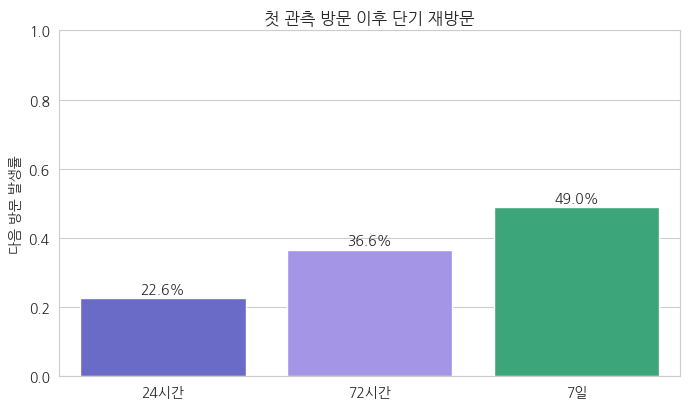

In [ ]:
# 후속 관찰기간을 확보한 첫 방문 재방문율
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    first_visits = visit_ordered[visit_ordered.observed_visit_no.eq(1)].copy()
    window_end = pd.Timestamp(visit_ordered.visit_start.max())
    first_visits['hours_to_next'] = (first_visits.next_visit_start - first_visits.visit_start).dt.total_seconds() / 3600
    first_visits['next_24h'] = (first_visits.hours_to_next <= 24).astype(int)
    first_visits['next_72h'] = (first_visits.hours_to_next <= 72).astype(int)
    first_visits['next_7d'] = (first_visits.hours_to_next <= 24 * 7).astype(int)
    first_visits['observable_7d'] = first_visits.visit_start <= window_end - pd.Timedelta(days=7)
    revisit_cohort = first_visits[first_visits.observable_7d].copy()
    revisit_rates = pd.DataFrame({'window': ['24시간', '72시간', '7일'], 'rate': [revisit_cohort.next_24h.mean(), revisit_cohort.next_72h.mean(), revisit_cohort.next_7d.mean()], 'users': [len(revisit_cohort)] * 3})
    display(save_table(revisit_rates, '39_revisit_rates'))
    plt.figure(figsize=(7, 4.2))
    ax = sns.barplot(data=revisit_rates, x='window', y='rate', palette=COLORS[:3])
    ax.set_ylim(0, 1)
    ax.set_ylabel('다음 방문 발생률')
    ax.set_xlabel('')
    ax.set_title('첫 관측 방문 이후 단기 재방문')
    for p, v in zip(ax.patches, revisit_rates.rate):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.015, f'{v:.1%}', ha='center')
    savefig('36_hackle_revisit_rates')


- 7일을 관찰할 수 있는 117,420명 기준이다. 24시간 내 재방문은 22.61%, 7일 내 재방문은 49.02%다.
- 관찰 종료까지 7일이 남지 않은 사용자는 분모에서 제외한다.


,first_visit_behavior,n_without,revisit_without,n_with,revisit_with,pp_difference
2,question_complete_flag,103659,0.4738,13761,0.6136,0.1398
3,question_skip_flag,107592,0.4803,9828,0.5992,0.1189
1,question_start_flag,95546,0.4782,21874,0.5426,0.0644
7,friend_flag,111591,0.4885,5829,0.5239,0.0355
8,chat_flag,98405,0.4958,19015,0.4615,-0.0343
5,notice_detail_flag,95580,0.5030,21840,0.4341,-0.0690
4,alarm_center_flag,83116,0.5255,34304,0.4048,-0.1207
6,browse_flag,50951,0.5592,66469,0.4373,-0.1219
0,question_surface_flag,59062,0.5585,58358,0.4211,-0.1373


/tmp/ipykernel_804/204426315.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=br, y='first_visit_behavior', x='pp_difference', palette=[COLORS[2] if x >= 0 else COLORS[4] for x in br.pp_difference])


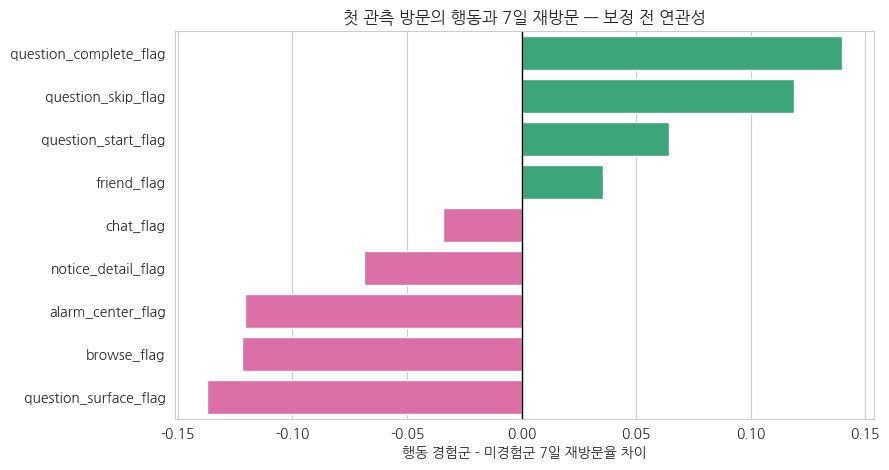

In [ ]:
# 첫 방문 행동 유무별 7일 재방문 비교
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    behavior_cols = ['question_surface_flag', 'question_start_flag', 'question_complete_flag', 'question_skip_flag', 'alarm_center_flag', 'notice_detail_flag', 'browse_flag', 'friend_flag', 'chat_flag']
    behavior_revisit = []
    for col in behavior_cols:
        g = revisit_cohort.groupby(col).next_7d.agg(['count', 'mean']).reset_index()
        if set(g[col]) == {0, 1}:
            behavior_revisit.append([col, int(g.loc[g[col].eq(0), 'count'].iloc[0]), g.loc[g[col].eq(0), 'mean'].iloc[0], int(g.loc[g[col].eq(1), 'count'].iloc[0]), g.loc[g[col].eq(1), 'mean'].iloc[0], g.loc[g[col].eq(1), 'mean'].iloc[0] - g.loc[g[col].eq(0), 'mean'].iloc[0]])
    br = pd.DataFrame(behavior_revisit, columns=['first_visit_behavior', 'n_without', 'revisit_without', 'n_with', 'revisit_with', 'pp_difference'])
    br = br.sort_values('pp_difference', ascending=False)
    display(save_table(br, '40_first_visit_behavior_revisit'))
    plt.figure(figsize=(9, 4.8))
    sns.barplot(data=br, y='first_visit_behavior', x='pp_difference', palette=[COLORS[2] if x >= 0 else COLORS[4] for x in br.pp_difference])
    plt.axvline(0, color='black', lw=1)
    plt.xlabel('행동 경험군 - 미경험군 7일 재방문율 차이')
    plt.ylabel('')
    plt.title('첫 관측 방문의 행동과 7일 재방문 — 보정 전 연관성')
    savefig('37_first_visit_behavior_revisit')


- 질문 완료 경험군의 7일 재방문율은 미경험군보다 13.98%p 높고, 알림 상세 경험군은 6.90%p 낮다.
- 방문 목적과 초기 이용 상태가 다른 사람의 단순 비교다. 뒤에서 활동량과 완료 전 조건을 맞춰 살펴본다.


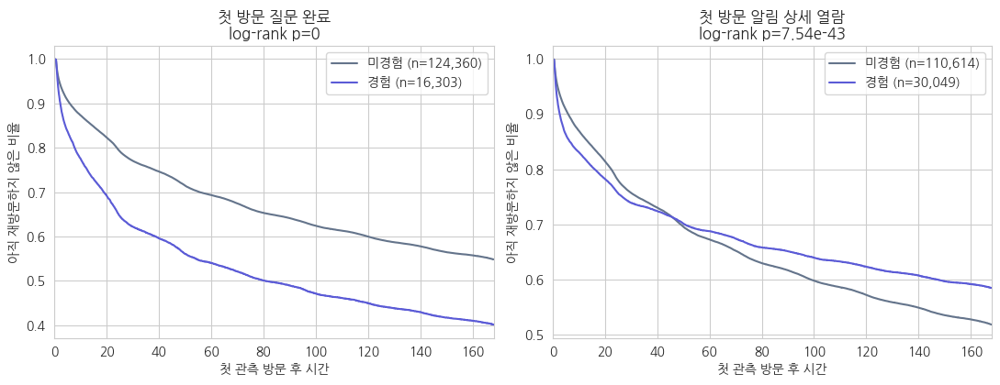

,group_variable,n0,n1,logrank_stat,p_value
0,question_complete_flag,124360,16303,"1,775.7862",0.0000
1,notice_detail_flag,110614,30049,188.2812,0.0000


In [ ]:
# 재방문까지의 시간 · 관찰 종료 검열
if INTERACTION_EVENT_DETAIL_AVAILABLE:

    def km_curve(duration_hours, event, max_hours=24 * 7):
        d = np.minimum(np.asarray(duration_hours, float), max_hours)
        e = np.asarray(event, int) & (np.asarray(duration_hours, float) <= max_hours)
        times = np.sort(np.unique(d[e.astype(bool)]))
        surv = 1.0
        rows = [(0.0, 1.0)]
        for t in times:
            at_risk = (d >= t).sum()
            events = ((d == t) & e.astype(bool)).sum()
            if at_risk:
                surv *= 1 - events / at_risk
            rows.append((t, surv))
        return pd.DataFrame(rows, columns=['hours', 'survival'])

    def logrank(d1, e1, d2, e2, max_hours=168):
        raw1 = np.asarray(d1, float)
        raw2 = np.asarray(d2, float)
        e1 = np.asarray(e1, bool) & (raw1 <= max_hours)
        e2 = np.asarray(e2, bool) & (raw2 <= max_hours)
        d1 = np.minimum(raw1, max_hours)
        d2 = np.minimum(raw2, max_hours)
        times = np.sort(np.unique(np.r_[d1[e1], d2[e2]]))
        oe = 0.0
        var = 0.0
        for t in times:
            n1 = (d1 >= t).sum()
            n2 = (d2 >= t).sum()
            d_1 = ((d1 == t) & e1).sum()
            d_2 = ((d2 == t) & e2).sum()
            n = n1 + n2
            dd = d_1 + d_2
            if n > 1:
                oe += d_1 - dd * n1 / n
                var += n1 * n2 * dd * (n - dd) / (n * n * (n - 1))
        z2 = oe * oe / var if var > 0 else 0
        return (z2, stats.chi2.sf(z2, 1))
    survival_base = first_visits.copy()
    survival_base['follow_hours'] = np.where(survival_base.next_visit_start.notna(), survival_base.hours_to_next, (window_end - survival_base.visit_start).dt.total_seconds() / 3600)
    survival_base['event_observed'] = survival_base.next_visit_start.notna().astype(int)
    fig, axs = plt.subplots(1, 2, figsize=(11, 4.3))
    surv_tests = []
    for ax, col, title in zip(axs, ['question_complete_flag', 'notice_detail_flag'], ['첫 방문 질문 완료', '첫 방문 알림 상세 열람']):
        curves = []
        for val, label, color in [(0, '미경험', COLORS[5]), (1, '경험', COLORS[0])]:
            g = survival_base[survival_base[col].eq(val)]
            km = km_curve(g.follow_hours, g.event_observed)
            km['group'] = label
            curves.append(km)
            ax.step(km.hours, km.survival, where='post', label=f'{label} (n={len(g):,})', color=color)
        a = survival_base[survival_base[col].eq(0)]
        b = survival_base[survival_base[col].eq(1)]
        stat, p = logrank(a.follow_hours, a.event_observed, b.follow_hours, b.event_observed)
        surv_tests.append([col, len(a), len(b), stat, p])
        ax.set_xlim(0, 168)
        ax.set_xlabel('첫 관측 방문 후 시간')
        ax.set_ylabel('아직 재방문하지 않은 비율')
        ax.set_title(f'{title}\nlog-rank p={p:.3g}')
        ax.legend()
    savefig('38_hackle_revisit_survival')
    display(save_table(pd.DataFrame(surv_tests, columns=['group_variable', 'n0', 'n1', 'logrank_stat', 'p_value']), '41_survival_logrank'))


- 질문 완료 경험 여부와 알림 상세 경험 여부 모두 재방문 시간 분포에 차이가 있다. 표본이 크므로 검정 유의성만으로 제품 효과를 판단하지 않는다.
- 곡선은 해당 시점까지 아직 재방문하지 않은 비율이다.


,k,silhouette
0,2,0.3952
1,3,0.3814
2,4,0.3657
3,5,0.3378
4,6,0.3402


,cluster,visits,median_events,median_seconds,question_surface_rate,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,browse_rate,friend_rate,chat_rate,next_7d,journey_type
0,0,26868,20.0000,171.0000,0.7119,0.6210,0.5311,0.4052,0.3118,0.7888,0.1063,0.2780,0.7143,탐색형 C0
1,1,53132,4.0000,12.0000,0.1878,0.0617,0.0208,0.0118,0.0482,0.3439,0.0101,0.0552,0.7274,탐색형 C1


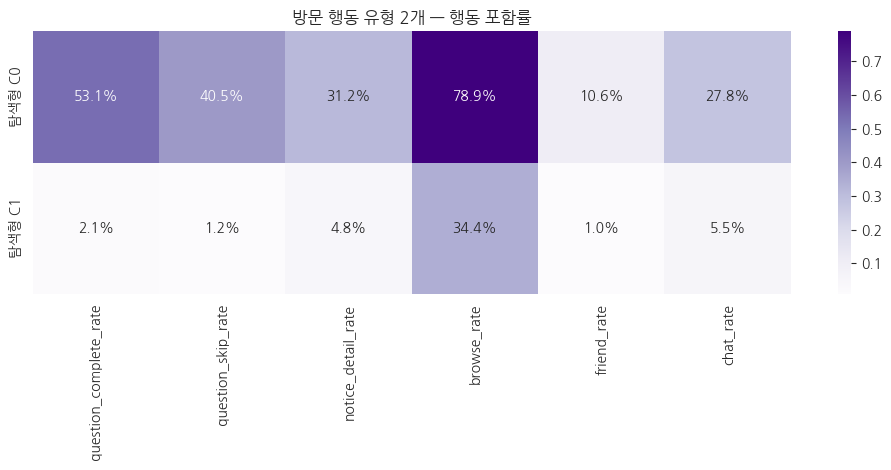

In [ ]:
# 방문 경로 군집 · 행동 구성 비교
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    cluster_cols = ['event_count', 'duration_seconds', 'question_surface_events', 'question_start_events', 'question_open_events', 'question_complete_events', 'question_skip_events', 'alarm_center_events', 'notice_detail_events', 'browse_events', 'friend_events', 'chat_events']
    cluster_df = visit_ordered[cluster_cols + ['visit_id', 'next_visit_start', 'visit_start']].copy()
    cluster_df[cluster_cols] = cluster_df[cluster_cols].fillna(0)
    for c in ['event_count', 'duration_seconds'] + cluster_cols[2:]:
        cluster_df[c] = np.log1p(cluster_df[c].clip(lower=0))
    sample = cluster_df.sample(min(80000, len(cluster_df)), random_state=42)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(sample[cluster_cols])
    sil = []
    for k in range(2, 7):
        km = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=4096, n_init=10).fit(Xs)
        idx = np.random.default_rng(42).choice(len(Xs), size=min(15000, len(Xs)), replace=False)
        sil.append([k, silhouette_score(Xs[idx], km.labels_[idx])])
    sil_df = pd.DataFrame(sil, columns=['k', 'silhouette'])
    best_k = int(sil_df.loc[sil_df.silhouette.idxmax(), 'k'])
    display(save_table(sil_df, '42_visit_cluster_k_selection'))
    km = MiniBatchKMeans(n_clusters=best_k, random_state=42, batch_size=4096, n_init=20).fit(Xs)
    sample['cluster'] = km.labels_
    raw_sample = visit_ordered.loc[sample.index].copy()
    raw_sample['cluster'] = sample.cluster
    raw_sample['next_7d'] = ((raw_sample.next_visit_start - raw_sample.visit_start).dt.total_seconds() / 3600 <= 168).astype(int)
    centers = raw_sample.groupby('cluster').agg(visits=('visit_id', 'nunique'), median_events=('event_count', 'median'), median_seconds=('duration_seconds', 'median'), question_surface_rate=('question_surface_flag', 'mean'), question_start_rate=('question_start_flag', 'mean'), question_complete_rate=('question_complete_flag', 'mean'), question_skip_rate=('question_skip_flag', 'mean'), notice_detail_rate=('notice_detail_flag', 'mean'), browse_rate=('browse_flag', 'mean'), friend_rate=('friend_flag', 'mean'), chat_rate=('chat_flag', 'mean'), next_7d=('next_7d', 'mean')).reset_index()
    action_cols = ['question_complete_rate', 'question_skip_rate', 'notice_detail_rate', 'browse_rate', 'friend_rate', 'chat_rate']
    labels = []
    label_map = {'question_complete_rate': '질문 완료형', 'question_skip_rate': '질문 스킵형', 'notice_detail_rate': '알림 확인형', 'browse_rate': '탐색형', 'friend_rate': '친구 행동형', 'chat_rate': '대화형'}
    for _, r in centers.iterrows():
        labels.append(label_map[max(action_cols, key=lambda c: r[c])])
    centers['journey_type'] = [f'{lab} C{int(c)}' for lab, c in zip(labels, centers.cluster)]
    display(save_table(centers, '43_visit_journey_clusters'))
    heat = centers.set_index('journey_type')[action_cols]
    plt.figure(figsize=(10, 4.8))
    sns.heatmap(heat, annot=True, fmt='.1%', cmap='Purples')
    plt.title(f'방문 행동 유형 {best_k}개 — 행동 포함률')
    plt.xlabel('')
    plt.ylabel('')
    savefig('39_visit_journey_clusters')


- 선택된 방문 군집은 2개였다. 두 집단 모두 탐색 행동 비율이 가장 높았지만, C0의 이벤트 수·관측 시간·질문 완료 비율이 C1보다 높았다.
- 방문 단위 행동 구분이며, 사람의 고정 성향이나 Value의 사용자 클러스터와 동일하지 않다.


,model,test_auc,features
0,방문 깊이만,0.5623,3
1,방문 깊이 + 상호작용,0.6275,13


,feature,standardized_coef,odds_ratio_per_1sd
2,distinct_event_count,1.2954,3.6525
10,browse_flag,-0.5927,0.5529
3,question_surface_flag,-0.5080,0.6017
1,duration_seconds,0.4387,1.5507
8,alarm_center_flag,-0.4221,0.6557
0,event_count,-0.3123,0.7318
5,question_open_flag,-0.2088,0.8115
4,question_start_flag,-0.1988,0.8197
12,chat_flag,-0.1227,0.8846
6,question_complete_flag,0.1159,1.1229


/tmp/ipykernel_804/4006124934.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top, y='feature', x='standardized_coef', palette=[COLORS[2] if x > 0 else COLORS[4] for x in top.standardized_coef])


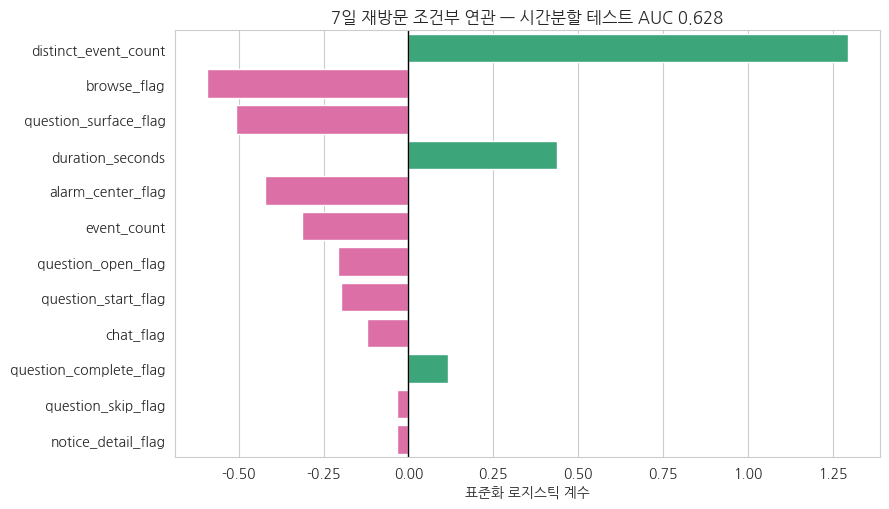

In [ ]:
# 방문 깊이·상호작용 변수의 재방문 예측
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    model_df = revisit_cohort.copy()
    model_features = ['event_count', 'duration_seconds', 'distinct_event_count', 'question_surface_flag', 'question_start_flag', 'question_open_flag', 'question_complete_flag', 'question_skip_flag', 'alarm_center_flag', 'notice_detail_flag', 'browse_flag', 'friend_flag', 'chat_flag']
    base_features = ['event_count', 'duration_seconds', 'distinct_event_count']
    cutoff = model_df.visit_start.quantile(0.7)
    train = model_df.visit_start <= cutoff
    test = ~train

    def fit_auc(cols):
        p = Pipeline([('imp', SimpleImputer(strategy='median')), ('scale', StandardScaler()), ('model', LogisticRegression(max_iter=3000, class_weight='balanced'))])
        p.fit(model_df.loc[train, cols], model_df.loc[train, 'next_7d'])
        return (p, roc_auc_score(model_df.loc[test, 'next_7d'], p.predict_proba(model_df.loc[test, cols])[:, 1]))
    base_model, base_auc = fit_auc(base_features)
    full_model, full_auc = fit_auc(model_features)
    model_compare = pd.DataFrame({'model': ['방문 깊이만', '방문 깊이 + 상호작용'], 'test_auc': [base_auc, full_auc], 'features': [len(base_features), len(model_features)]})
    display(save_table(model_compare, '44_revisit_model_comparison'))
    coef = pd.DataFrame({'feature': model_features, 'standardized_coef': full_model.named_steps['model'].coef_[0]})
    coef['odds_ratio_per_1sd'] = np.exp(coef.standardized_coef)
    coef = coef.sort_values('standardized_coef', key=abs, ascending=False)
    display(save_table(coef, '45_revisit_model_coefficients'))
    plt.figure(figsize=(9, 5.2))
    top = coef.head(12)
    sns.barplot(data=top, y='feature', x='standardized_coef', palette=[COLORS[2] if x > 0 else COLORS[4] for x in top.standardized_coef])
    plt.axvline(0, color='black', lw=1)
    plt.title(f'7일 재방문 조건부 연관 — 시간분할 테스트 AUC {full_auc:.3f}')
    plt.xlabel('표준화 로지스틱 계수')
    plt.ylabel('')
    savefig('40_revisit_model_coefficients')


- 테스트 ROC-AUC는 방문 깊이 모형 0.5623, 상호작용 추가 모형 0.6275다.
- 예측에 도움이 된다는 결과이지 해당 행동이 재방문을 일으켰다는 인과 증거는 아니다.


In [ ]:
# 식별 사용자 범위별 비교 · Ping 계측 한계
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    robust = con.execute("\n    SELECT\n      CASE WHEN identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL AND COALESCE(is_staff,0)=0 THEN '식별 비운영 사용자 방문' ELSE '그 외 방문' END population,\n      COUNT(*) visits, AVG(question_start_flag) question_start_rate,\n      AVG(question_complete_flag) question_complete_rate,\n      AVG(question_skip_flag) question_skip_rate,\n      AVG(notice_detail_flag) notice_detail_rate,\n      AVG(CAST(event_count=1 AS INTEGER)) single_event_visit_rate\n    FROM hackle_visit_interaction GROUP BY 1\n    ").df()
    display(save_table(robust, '46_population_robustness'))
    instrumentation = pd.DataFrame([['Hackle 공식 Ping 열람', 'open_ping', int(key_check.loc[key_check.event_key.eq('open_ping'), 'events'].iloc[0]), '직접 분석 불가'], ['결과 확인 대리 경로', 'click_appbar_alarm_center → click_notice_detail', int(key_check.loc[key_check.event_key.eq('click_notice_detail'), 'events'].iloc[0]), '별도 대리경로로만 해석'], ['방문 분리', '30분 무활동', '-', '동일 추적키 내 30분 무활동 기준으로 분석용 방문 복원'], ['시간대', '원시 event_at', '-', '+9시간 임의 보정 없음'], ['첫 방문', '관찰창 내 첫 방문', '-', '생애 최초 방문으로 해석 금지']], columns=['점검항목', '정의', '관측량', '판단'])
    display(save_table(instrumentation, '47_instrumentation_limits'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,population,visits,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,single_event_visit_rate
0,식별 비운영 사용자 방문,626987,0.2480,0.1917,0.1425,0.1355,0.0120
1,그 외 방문,269022,0.1733,0.1113,0.0789,0.1671,0.0263


,점검항목,정의,관측량,판단
0,Hackle 공식 Ping 열람,open_ping,0,직접 분석 불가
1,결과 확인 대리 경로,click_appbar_alarm_center → click_notice_detail,229358,별도 대리경로로만 해석
2,방문 분리,30분 무활동,-,동일 추적키 내 30분 무활동 기준으로 분석용 방문 복원
3,시간대,원시 event_at,-,+9시간 임의 보정 없음
4,첫 방문,관찰창 내 첫 방문,-,생애 최초 방문으로 해석 금지


- 식별 비운영 사용자 방문의 질문 시작·완료 비율은 24.80%·19.17%, 그 외 방문은 17.33%·11.13%다.
- 사용자 연결 여부에 따라 행동 구성이 달라 전체 방문 평균을 식별 사용자의 행동으로 그대로 적용하기 어렵다.


In [ ]:
# DB·로그별 확인 결과 정리
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    get = lambda df, col: float(df[col].iloc[0])
    final_findings = pd.DataFrame([['5월 질문', '생성→1개 이상 투표', float(funnel.loc[funnel.stage.eq('1개 이상 투표 기록'), 'share_of_created'].iloc[0]), '바이럴 직후 질문 기능의 실제 사용 연결'], ['5월 질문', '생성→10개 완료 대리', float(funnel.loc[funnel.stage.eq('10개 투표 완료 대리'), 'share_of_created'].iloc[0]), '질문세트 끝까지 소비 여부'], ['5월 질문', '첫 세트→7일 내 다음 세트', float(rates.loc[rates.window.eq('7일'), 'next_set_rate'].iloc[0]), '일회성 질문 소비 여부'], ['Hackle', '방문 중 질문 시작', get(visit_summary, 'question_start_visit_rate'), '7~8월 관측 사용자의 질문 진입'], ['Hackle', '방문 중 질문 완료', get(visit_summary, 'question_complete_visit_rate'), '질문 행동의 완료'], ['Hackle', '첫 관측 방문→7일 내 재방문', float(revisit_rates.loc[revisit_rates.window.eq('7일'), 'rate'].iloc[0]), '후속 방문 연결'], ['Hackle', '공식 open_ping 관측', int(key_check.loc[key_check.event_key.eq('open_ping'), 'events'].iloc[0]), 'Ping 루프는 계측 공백으로 확정 불가']], columns=['자료', '핵심지표', '값', '판단에 쓰는 질문'])
    display(save_table(final_findings, '50_final_findings'))
    strongest = br.iloc[0]
    display(Markdown(f'\n**주요 결과**\n\n- 첫 관측 방문의 `{strongest.first_visit_behavior}` 경험군과 미경험군의 7일 재방문율 차이는 {strongest.pp_difference:+.1%}p였다.\n- 5월 DB의 질문 반복 이용과 7~8월 로그의 앱 재방문은 따로 살펴봤다. 다음 Value에서는 선택받은 경험과 결과 확인·관계 반응을 후기 활동에 연결한다.\n'))


,자료,핵심지표,값,판단에 쓰는 질문
0,5월 질문,생성→1개 이상 투표,0.9724,바이럴 직후 질문 기능의 실제 사용 연결
1,5월 질문,생성→10개 완료 대리,0.3315,질문세트 끝까지 소비 여부
2,5월 질문,첫 세트→7일 내 다음 세트,0.9703,일회성 질문 소비 여부
3,Hackle,방문 중 질문 시작,0.2255,7~8월 관측 사용자의 질문 진입
4,Hackle,방문 중 질문 완료,0.1676,질문 행동의 완료
5,Hackle,첫 관측 방문→7일 내 재방문,0.4902,후속 방문 연결
6,Hackle,공식 open_ping 관측,0.0000,Ping 루프는 계측 공백으로 확정 불가



**주요 결과**

- 첫 관측 방문의 `question_complete_flag` 경험군과 미경험군의 7일 재방문율 차이는 +14.0%p였다.
- 5월 DB의 질문 반복 이용과 7~8월 로그의 앱 재방문은 따로 살펴봤다. 다음 Value에서는 선택받은 경험과 결과 확인·관계 반응을 후기 활동에 연결한다.


- 5월 질문 이용자는 다음 세트를 많이 생성했다. 7~8월 전체 방문에서는 질문을 시작한 방문 자체가 22.55%였다. 질문을 이미 이용한 사람의 반복 이용과 전체 방문에서 질문을 시작하는 비율은 서로 다른 문제다.


In [ ]:
# Interaction 기본 분석 조건 점검
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    qa_final = pd.DataFrame([['분석 입력 캐시 연결', all(p.is_file() for p in interaction_cache_paths.values()), '사용자 식별자와 이벤트 순서가 포함된 캐시 7개'], ['5월과 7~8월 모집단 분리', True, '통합 비교 없음'], ['5월 질문세트·질문조각·투표 eligible 필터', True, '정제 마트 플래그 적용'], ['5월 말 7일 후속 관찰 보완', True, '전체 질문세트 이력에서 다음 세트만 추적'], ['Hackle 사용자 분석 식별자 제한', True, 'IDENTIFIED_SERVICE_USER·비운영 사용자'], ['재방문 7일 우측 검열', True, '관찰 종료 7일 이전 첫 방문만 비율 계산'], ['이벤트 순서 반영', True, 'visit_id + event_order 사용'], ['Ping 계측 공백 명시', True, 'open_ping 0건, 알림 경로와 분리'], ['시간대 임의 보정 금지', True, '원시 시각 유지'], ['인과 표현 금지', True, '연관성·대리지표로 표기'], ['표·차트 화면 출력', True, 'CSV·PNG 파일 생성 없이 결과 변수와 셀 출력 사용']], columns=['check', 'pass', 'evidence'])
    display(save_table(qa_final, '99_final_qa'))
    assert qa_final['pass'].all()
    print(f"FINAL QA: PASS {qa_final['pass'].sum()} / FAIL 0")
team7_release_unused('320', 'Interaction 기본 분석 완료')


,check,pass,evidence
0,GitHub 원문 입력 캐시 연결,True,원문 interaction_core 출력 캐시 7개; 임의 사용자 복원 없음
1,5월과 7~8월 모집단 분리,True,통합 비교 없음
2,5월 질문세트·질문조각·투표 eligible 필터,True,정제 마트 플래그 적용
3,5월 말 7일 후속 관찰 보완,True,전체 질문세트 이력에서 다음 세트만 추적
4,Hackle 사용자 분석 식별자 제한,True,IDENTIFIED_SERVICE_USER·비운영 사용자
5,재방문 7일 우측 검열,True,관찰 종료 7일 이전 첫 방문만 비율 계산
6,이벤트 순서 반영,True,visit_id + event_order 사용
7,Ping 계측 공백 명시,True,"open_ping 0건, 알림 경로와 분리"
8,시간대 임의 보정 금지,True,원시 시각 유지
9,인과 표현 금지,True,연관성·대리지표로 표기


FINAL QA: PASS 11 / FAIL 0
[Interaction 기본 분석 완료] 사용이 끝난 변수 61개 정리
[Interaction 기본 분석 완료] Python 사용 RAM 3.80 GB / 시스템 여유 RAM 8.38 GB


- 모집단 분리·7일 관찰창·이벤트 순서 정의를 유지한다. `open_ping` 0건을 실제 열람이 없었다는 의미로 해석하지 않는다.


### 3-4-5. 완료 기록의 누락과 실제 재진입 구분

- 낮은 완료 대리지표가 기록 누락 때문인지 살펴봤다. 다음 세트 생성도 30분 안의 연속 이용과 날짜가 바뀐 뒤의 재진입으로 나눴다.


,structure_band,question_sets,set_share,mean_expected_piece_count,any_vote_rate,mean_vote_coverage,complete10_rate
0,0개 연결,1441,0.0101,10.0000,0.0000,NaN,0.0000
1,1~9개 연결,91307,0.6378,10.0000,0.9999,0.9999,0.0000
2,10개 연결,50410,0.3521,10.0000,0.9505,0.9440,0.9416


,total_sets,structurally_incomplete_sets,structurally_complete_sets,behavior_incomplete_among_complete_structure,complete10_sets,behavior_completion_rate_given_structure
0,143158,"92,748.0000","50,410.0000","2,946.0000","47,464.0000",0.9416


/tmp/ipykernel_804/3958615207.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_loss, x='구분', y='share', palette=[COLORS[5], COLORS[3], COLORS[2]])


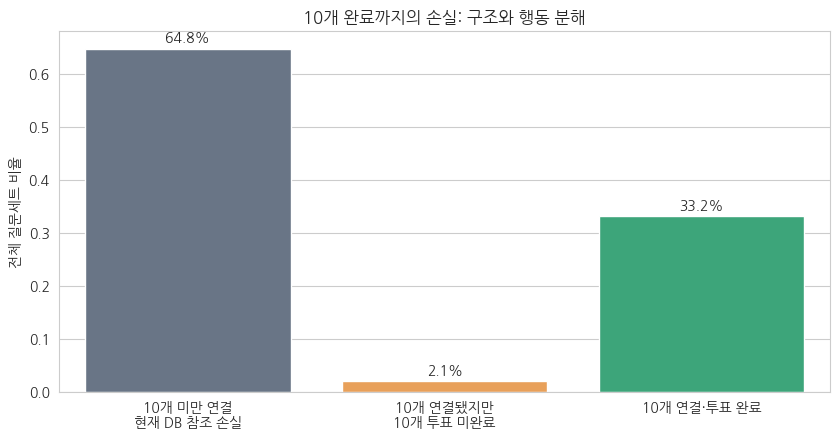

세트마다 10개를 참조하지만 연결된 질문조각이 부족했다. 완료 대리지표 33.2%에는 이 기록 누락이 섞여 있다. 실제 화면 노출 수는 알 수 없다.

In [ ]:
# 질문조각 연결 부족 · 투표 미완료 분해
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    structure_decomp = con.execute("\n    SELECT\n      CASE WHEN mapped_pieces=0 THEN '0개 연결'\n           WHEN mapped_pieces BETWEEN 1 AND 9 THEN '1~9개 연결'\n           WHEN mapped_pieces=10 THEN '10개 연결'\n           ELSE '11개 이상 연결' END AS structure_band,\n      COUNT(*) question_sets,\n      COUNT(*)/SUM(COUNT(*)) OVER() AS set_share,\n      AVG(expected_piece_count) mean_expected_piece_count,\n      AVG(any_vote_flag) any_vote_rate,\n      AVG(vote_coverage) mean_vote_coverage,\n      AVG(completed_10_proxy) complete10_rate\n    FROM may_set_metrics GROUP BY 1\n    ORDER BY MIN(mapped_pieces)\n    ").df()
    display(save_table(structure_decomp, '60_completion_structure_decomposition'))
    loss = con.execute('\n    SELECT\n      COUNT(*) total_sets,\n      SUM(mapped_pieces<10) structurally_incomplete_sets,\n      SUM(mapped_pieces>=10) structurally_complete_sets,\n      SUM(mapped_pieces>=10 AND voted_pieces<10) behavior_incomplete_among_complete_structure,\n      SUM(mapped_pieces>=10 AND voted_pieces>=10) complete10_sets,\n      AVG(CASE WHEN mapped_pieces>=10 THEN CAST(voted_pieces>=10 AS INTEGER) END) behavior_completion_rate_given_structure\n    FROM may_set_metrics\n    ').df()
    display(save_table(loss, '61_completion_loss_decomposition'))
    plot_loss = pd.DataFrame({'구분': ['10개 미만 연결\n현재 DB 참조 손실', '10개 연결됐지만\n10개 투표 미완료', '10개 연결·투표 완료'], 'sets': [int(loss.structurally_incomplete_sets.iloc[0]), int(loss.behavior_incomplete_among_complete_structure.iloc[0]), int(loss.complete10_sets.iloc[0])]})
    plot_loss['share'] = plot_loss.sets / plot_loss.sets.sum()
    plt.figure(figsize=(8.5, 4.5))
    ax = sns.barplot(data=plot_loss, x='구분', y='share', palette=[COLORS[5], COLORS[3], COLORS[2]])
    ax.set_ylabel('전체 질문세트 비율')
    ax.set_xlabel('')
    ax.set_title('10개 완료까지의 손실: 구조와 행동 분해')
    for p, v in zip(ax.patches, plot_loss.share):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.012, f'{v:.1%}', ha='center')
    savefig('50_completion_loss_decomposition')
    display(Markdown('세트마다 10개를 참조하지만 연결된 질문조각이 부족했다. 완료 대리지표 33.2%에는 이 기록 누락이 섞여 있다. 실제 화면 노출 수는 알 수 없다.'))


- 전체 세트의 64.79%는 연결된 질문조각이 10개 미만이었다. 전체 완료 대리지표 33.15%에는 이런 기록 구조가 크게 작용했다.
- 질문조각 10개가 모두 연결된 세트만 보면 10개 투표 기록 비율은 94.16%였다. 분모를 바꾸자 결과가 크게 달라졌다.


In [ ]:
# 30분 질문 이용 묶음 · 다음 활성일 구성
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    con.execute('\n    CREATE OR REPLACE TEMP VIEW qset_bursts_all AS\n    WITH o AS (\n      SELECT owner_user_id,question_set_id,set_created_at,school_id,\n             LAG(set_created_at) OVER(PARTITION BY owner_user_id ORDER BY set_created_at,question_set_id) prev_at\n      FROM question_set_all\n      WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL\n    ), tagged AS (\n      SELECT *, CASE WHEN prev_at IS NULL OR set_created_at>prev_at+INTERVAL 30 MINUTE THEN 1 ELSE 0 END new_burst\n      FROM o\n    )\n    SELECT *, SUM(new_burst) OVER(PARTITION BY owner_user_id ORDER BY set_created_at,question_set_id) AS burst_id\n    FROM tagged\n    ')
    con.execute('\n    CREATE OR REPLACE TEMP VIEW qset_burst_summary_all AS\n    WITH b AS (\n      SELECT owner_user_id,burst_id,MIN(set_created_at) burst_start,MAX(set_created_at) burst_end,\n             COUNT(*) qsets_in_burst,COUNT(DISTINCT CAST(set_created_at AS DATE)) active_days,\n             ANY_VALUE(school_id) school_id\n      FROM qset_bursts_all GROUP BY 1,2\n    )\n    SELECT *, LEAD(burst_start) OVER(PARTITION BY owner_user_id ORDER BY burst_start,burst_id) next_burst_start\n    FROM b\n    ')
    first_may_burst = con.execute("\n    WITH x AS (\n      SELECT *,ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY burst_start,burst_id) rn_may\n      FROM qset_burst_summary_all\n      WHERE burst_start>=TIMESTAMP '2023-05-01' AND burst_start<TIMESTAMP '2023-06-01'\n    )\n    SELECT *,date_diff('minute',burst_end,next_burst_start)/60.0 hours_to_next_burst,\n           CASE WHEN next_burst_start<=burst_end+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_burst_24h,\n           CASE WHEN next_burst_start<=burst_end+INTERVAL 72 HOUR THEN 1 ELSE 0 END next_burst_72h,\n           CASE WHEN next_burst_start<=burst_end+INTERVAL 7 DAY THEN 1 ELSE 0 END next_burst_7d\n    FROM x WHERE rn_may=1\n    ").df()
    display(save_table(first_may_burst, '62_first_may_question_burst'))
    first_may_day = con.execute("\n    WITH days AS (\n      SELECT owner_user_id,CAST(set_created_at AS DATE) activity_date,ANY_VALUE(school_id) school_id,\n             COUNT(*) qsets_in_day\n      FROM question_set_all\n      WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL\n      GROUP BY 1,2\n    ), seq AS (\n      SELECT *,LEAD(activity_date) OVER(PARTITION BY owner_user_id ORDER BY activity_date) next_activity_date\n      FROM days\n    ), may AS (\n      SELECT *,ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY activity_date) rn_may\n      FROM seq WHERE activity_date BETWEEN DATE '2023-05-01' AND DATE '2023-05-31'\n    )\n    SELECT *,CASE WHEN next_activity_date<=activity_date+7 THEN 1 ELSE 0 END next_active_day_7d\n    FROM may WHERE rn_may=1\n    ").df()
    display(save_table(first_may_day, '62b_first_may_active_day'))


,owner_user_id,burst_id,burst_start,burst_end,qsets_in_burst,active_days,school_id,next_burst_start,rn_may,hours_to_next_burst,next_burst_24h,next_burst_72h,next_burst_7d
0,1171029,1.0000,2023-05-12 11:14:43,2023-05-12 11:35:52,2,1,1478,2023-05-12 12:22:14,1,0.7833,1,1,1
1,1182054,1.0000,2023-05-13 10:08:17,2023-05-13 10:09:22,2,1,1719,2023-05-13 11:16:40,1,1.1167,1,1,1
2,1185443,1.0000,2023-05-12 15:12:19,2023-05-12 15:14:43,2,1,5491,2023-05-13 00:39:55,1,9.4167,1,1,1
3,1190196,1.0000,2023-05-13 15:49:55,2023-05-13 16:03:35,2,1,5491,2023-05-14 01:08:04,1,9.0833,1,1,1
4,1190676,1.0000,2023-05-13 00:44:29,2023-05-13 00:46:51,2,1,1478,2023-05-13 03:48:59,1,3.0333,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4904,962981,1.0000,2023-05-09 08:47:19,2023-05-09 08:50:45,2,1,5520,2023-05-09 09:57:11,1,1.1167,1,1,1
4905,976297,1.0000,2023-05-10 17:54:09,2023-05-10 17:55:23,2,1,5491,2023-05-11 03:11:15,1,9.2667,1,1,1
4906,989039,1.0000,2023-05-08 03:26:38,2023-05-08 03:27:53,2,1,369,2023-05-08 10:15:44,1,6.8000,1,1,1
4907,990320,1.0000,2023-05-08 05:27:08,2023-05-08 05:36:34,2,1,352,2023-05-08 07:56:39,1,2.3333,1,1,1


,owner_user_id,activity_date,school_id,qsets_in_day,next_activity_date,rn_may,next_active_day_7d
0,1439168,2023-05-21,4426,1,2023-05-22,1,1
1,1445296,2023-05-22,5520,5,2023-05-23,1,1
2,1446883,2023-05-22,4426,10,2023-05-23,1,1
3,1447378,2023-05-22,4426,7,2023-05-23,1,1
4,1449592,2023-05-22,4426,4,2023-05-23,1,1
...,...,...,...,...,...,...,...
4904,971847,2023-05-09,5491,2,2023-05-10,1,1
4905,979523,2023-05-09,5491,3,2023-05-10,1,1
4906,979996,2023-05-08,1478,4,2023-05-09,1,1
4907,989503,2023-05-08,369,3,NaT,1,0


- 세트 생성 간격이 30분 이상이면 새 이용 묶음으로 나눴다. 날짜가 다른 다음 질문 활동도 따로 연결해 당일 연속 이용과 이후 재진입을 나눴다.


,next_qset_band,users,share
0,같은 30분 묶음,3223,0.6565
1,30분~24시간,1361,0.2772
2,1~3일,150,0.0306
3,3~7일,29,0.0059
4,7일 이후,25,0.0051
5,후속 세트 없음,121,0.0246


,지표,rate
0,다음 질문세트 24시간,0.9338
1,다음 질문세트 7일,0.9703
2,다음 30분 묶음 24시간,0.8890
3,다음 30분 묶음 7일,0.9542
4,다음 활성일 7일,0.9411


/tmp/ipykernel_804/1648117279.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=continuation_compare, x='지표', y='rate', palette=[COLORS[0], COLORS[1], COLORS[3], COLORS[4]])
/tmp/ipykernel_804/1648117279.py:13: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=continuation_compare, x='지표', y='rate', palette=[COLORS[0], COLORS[1], COLORS[3], COLORS[4]])


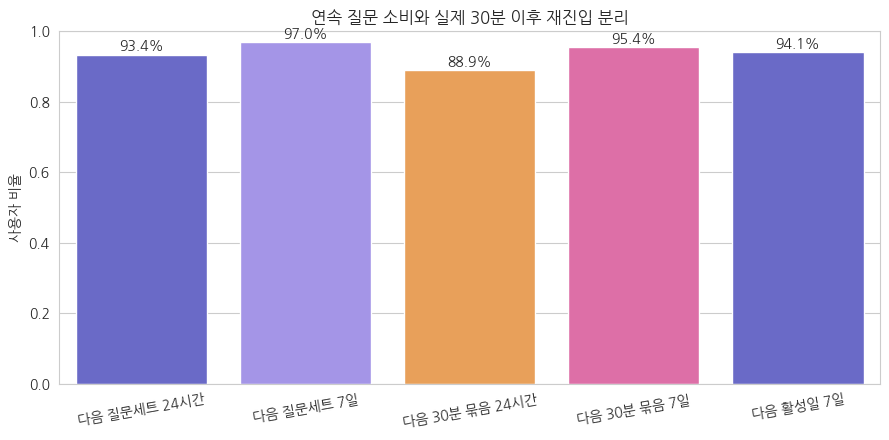

In [ ]:
# 연속 질문 소비와 이후 재진입 비교
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    first_next = followup[['owner_user_id', 'hours_to_next', 'next_24h', 'next_72h', 'next_7d']].copy()
    first_next['next_qset_band'] = pd.cut(first_next.hours_to_next, [-np.inf, 0.5, 24, 72, 168, np.inf], labels=['같은 30분 묶음', '30분~24시간', '1~3일', '3~7일', '7일 이후'])
    first_next['next_qset_band'] = first_next.next_qset_band.astype(object).fillna('후속 세트 없음')
    band_order = ['같은 30분 묶음', '30분~24시간', '1~3일', '3~7일', '7일 이후', '후속 세트 없음']
    next_band = first_next.groupby('next_qset_band').size().reindex(band_order, fill_value=0).rename('users').reset_index()
    next_band['share'] = next_band.users / next_band.users.sum()
    display(save_table(next_band, '63_next_qset_interval_bands'))
    continuation_compare = pd.DataFrame({'지표': ['다음 질문세트 24시간', '다음 질문세트 7일', '다음 30분 묶음 24시간', '다음 30분 묶음 7일', '다음 활성일 7일'], 'rate': [followup.next_24h.mean(), followup.next_7d.mean(), first_may_burst.next_burst_24h.mean(), first_may_burst.next_burst_7d.mean(), first_may_day.next_active_day_7d.mean()]})
    display(save_table(continuation_compare, '64_same_burst_vs_return'))
    plt.figure(figsize=(9, 4.5))
    ax = sns.barplot(data=continuation_compare, x='지표', y='rate', palette=[COLORS[0], COLORS[1], COLORS[3], COLORS[4]])
    ax.set_ylim(0, 1)
    ax.set_ylabel('사용자 비율')
    ax.set_xlabel('')
    ax.set_title('연속 질문 소비와 실제 30분 이후 재진입 분리')
    for p, v in zip(ax.patches, continuation_compare.rate):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.012, f'{v:.1%}', ha='center')
    plt.xticks(rotation=10)
    savefig('51_same_burst_vs_return')


- 첫 세트 이후 다음 세트가 같은 30분 묶음에 속한 사용자는 65.65%였다.
- 7일 내 다음 세트 생성률은 97.03%, 다른 활성일의 재진입률은 94.11%였다. 연속 생성을 제외해도 이후 질문 이용이 많았다.


In [ ]:
# 콘텐츠 특성과 다음 활성일의 보정 관계
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    content_qset = qset_follow.copy()
    content_qset['qset_at'] = pd.to_datetime(content_qset['qset_at'], errors='coerce')
    content_qset['next_qset_at'] = pd.to_datetime(content_qset['next_qset_at'], errors='coerce')
    content_qset['question_set_id'] = content_qset.question_set_id.astype(str)
    user_day_outcomes = con.execute("\n    WITH days AS (\n      SELECT owner_user_id,CAST(set_created_at AS DATE) activity_date,ANY_VALUE(school_id) school_id,COUNT(*) qsets_in_day\n      FROM question_set_all WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL\n      GROUP BY 1,2\n    ), seq AS (\n      SELECT *,LEAD(activity_date) OVER(PARTITION BY owner_user_id ORDER BY activity_date) next_activity_date FROM days\n    )\n    SELECT *,CASE WHEN next_activity_date<=activity_date+7 THEN 1 ELSE 0 END next_active_day_7d\n    FROM seq WHERE activity_date BETWEEN DATE '2023-05-01' AND DATE '2023-05-31'\n    ").df()
    user_day_outcomes['owner_user_id'] = user_day_outcomes.owner_user_id.astype(str)
    user_day_outcomes['activity_date'] = pd.to_datetime(user_day_outcomes.activity_date)
    cq = content_qset[content_qset.month.eq('2023-05')].copy()
    cq['owner_user_id'] = cq.owner_user_id.astype(str)
    cq['activity_date'] = cq.qset_at.dt.normalize()
    day_content = cq.groupby(['owner_user_id', 'activity_date']).agg(mean_exhaustion=('content_exhaustion_index', 'mean'), mean_semantic_repeat=('semantic_repeat_rate', 'mean'), mean_theme_diversity=('theme_diversity', 'mean'), mean_semantic_novelty=('mean_semantic_novelty', 'mean'), mean_candidate_entropy=('candidate_relation_entropy', 'mean'), mean_candidate_unique=('candidate_unique_ratio', 'mean'), mean_vote_rate=('vote_rate', 'mean'), content_qsets=('question_set_id', 'nunique')).reset_index()
    burst_content = day_content.merge(user_day_outcomes, on=['owner_user_id', 'activity_date'], how='inner')
    for c in ['mean_exhaustion', 'mean_semantic_repeat', 'mean_theme_diversity', 'mean_semantic_novelty', 'mean_candidate_entropy', 'mean_candidate_unique', 'mean_vote_rate']:
        burst_content['z_' + c] = (burst_content[c] - burst_content[c].mean()) / burst_content[c].std()
    burst_content['log_qsets'] = np.log1p(burst_content.qsets_in_day)
    burst_content['start_day'] = burst_content.activity_date.dt.day
    model_cols = ['z_mean_exhaustion', 'z_mean_semantic_repeat', 'z_mean_theme_diversity', 'z_mean_semantic_novelty', 'z_mean_candidate_entropy', 'z_mean_candidate_unique', 'log_qsets', 'start_day']
    bm = burst_content.dropna(subset=['next_active_day_7d'] + model_cols).copy()
    fit = smf.glm('next_active_day_7d ~ z_mean_exhaustion + z_mean_semantic_repeat + z_mean_theme_diversity + z_mean_semantic_novelty + z_mean_candidate_entropy + z_mean_candidate_unique + log_qsets + start_day + C(school_id)', data=bm, family=sm.families.Binomial(), eval_env=-1).fit(cov_type='cluster', cov_kwds={'groups': bm.owner_user_id})
    keep = [x for x in fit.params.index if x in model_cols]
    content_return_model = pd.DataFrame({'feature': keep, 'coef': fit.params[keep], 'odds_ratio': np.exp(fit.params[keep]), 'ci_low': np.exp(fit.conf_int().loc[keep, 0]), 'ci_high': np.exp(fit.conf_int().loc[keep, 1]), 'p_value': fit.pvalues[keep]}).reset_index(drop=True)
    display(save_table(content_return_model, '65_content_to_next_active_day_model'))
    exhaustion_row = content_return_model[content_return_model.feature.eq('z_mean_exhaustion')].iloc[0]
    novelty_row = content_return_model[content_return_model.feature.eq('z_mean_semantic_novelty')].iloc[0]
    display(Markdown(f'학교·활동일·당일 이용량을 보정한 종합 소진지수(p={exhaustion_row.p_value:.3f})와 의미 신규성(p={novelty_row.p_value:.3f}) 모두 다음 활성일 이용 감소와의 관계가 뚜렷하지 않았다. 활동적인 이용자가 남는 차이는 여전히 있을 수 있다.'))


/usr/local/lib/python3.13/dist-packages/statsmodels/formula/formulatools.py:70: FutureWarning: EvalEnvironment is deprecated and support be removed in a future version. You can
pass variables using a dict[str, value] where str is the variable name and the
value is the array of values.

  result = mgr.get_matrices(


,feature,coef,odds_ratio,ci_low,ci_high,p_value
0,z_mean_exhaustion,-0.1293,0.8787,0.7274,1.0614,0.1797
1,z_mean_semantic_repeat,0.3413,1.4068,1.2601,1.5705,0.0000
2,z_mean_theme_diversity,0.1950,1.2154,1.1010,1.3416,0.0001
3,z_mean_semantic_novelty,-0.0214,0.9789,0.9437,1.0153,0.2521
4,z_mean_candidate_entropy,0.0716,1.0742,1.0148,1.1371,0.0137
5,z_mean_candidate_unique,-0.4737,0.6227,0.5429,0.7142,0.0000
6,log_qsets,1.4498,4.2624,3.8563,4.7113,0.0000
7,start_day,-0.0470,0.9541,0.9473,0.9609,0.0000


학교·활동일·당일 이용량을 보정한 종합 소진지수(p=0.180)와 의미 신규성(p=0.252) 모두 다음 활성일 이용 감소와의 관계가 뚜렷하지 않았다. 활동적인 이용자가 남는 차이는 여전히 있을 수 있다.

- 소진지수의 오즈비는 0.8787, 95% 신뢰구간은 0.7274~1.0614였다. 다음 활성일 이용과의 관계는 통계적으로 유의하지 않았다.
- 테마 다양성과 후보 관계 엔트로피는 다음 활성일 이용과 양의 관계를 보였다.


,exhaustion_quintile,user_days,users,mean_exhaustion,next_active_day_7d,mean_qsets
0,"(0.241, 0.417]",8265,2922,0.3556,0.8651,2.7347
1,"(0.417, 0.478]",8243,3388,0.4496,0.9028,3.4558
2,"(0.478, 0.524]",8254,3446,0.5007,0.9162,3.7955
3,"(0.524, 0.574]",8254,3207,0.5478,0.9077,3.9140
4,"(0.574, 0.921]",8254,2607,0.6201,0.8824,3.4054


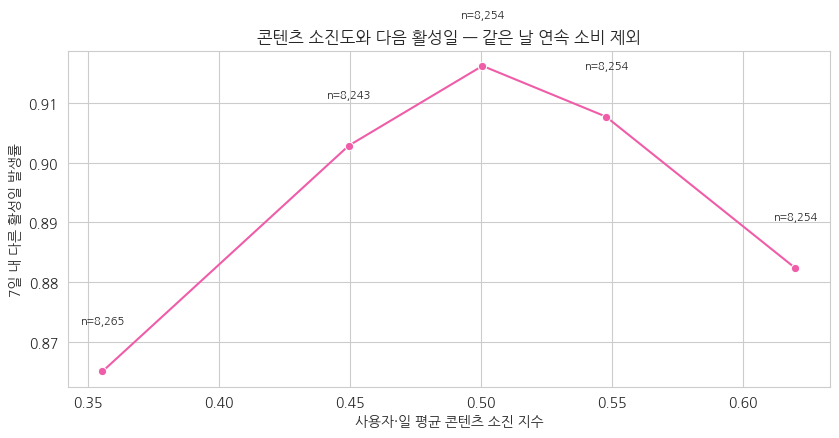

In [ ]:
# 소진지수 구간별 다음 활성일 이용
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    burst_content['exhaustion_quintile'] = pd.qcut(burst_content.mean_exhaustion, 5, duplicates='drop')
    exhaustion_return = burst_content.groupby('exhaustion_quintile', observed=True).agg(user_days=('activity_date', 'size'), users=('owner_user_id', 'nunique'), mean_exhaustion=('mean_exhaustion', 'mean'), next_active_day_7d=('next_active_day_7d', 'mean'), mean_qsets=('qsets_in_day', 'mean')).reset_index()
    display(save_table(exhaustion_return, '66_exhaustion_and_true_return'))
    plt.figure(figsize=(8.5, 4.5))
    ax = sns.lineplot(data=exhaustion_return, x='mean_exhaustion', y='next_active_day_7d', marker='o', color=COLORS[4])
    ax.set_xlabel('사용자·일 평균 콘텐츠 소진 지수')
    ax.set_ylabel('7일 내 다른 활성일 발생률')
    ax.set_title('콘텐츠 소진도와 다음 활성일 — 같은 날 연속 소비 제외')
    for _, r in exhaustion_return.iterrows():
        ax.text(r.mean_exhaustion, r.next_active_day_7d + 0.008, f'n={int(r.user_days):,}', ha='center', fontsize=8)
    savefig('52_exhaustion_true_return')


- 7일 내 다음 활성일 이용률은 소진지수 최저 구간 86.51%, 중간 구간 91.62%, 최고 구간 88.24%였다. 소진지수가 높을수록 일관되게 낮아지는 형태는 아니었다.
- 구간별 이용량과 사용자 구성이 달라 소진지수 하나로 재진입을 설명하기 어렵다.


,window,recipients,mean_bursts_before,mean_bursts_after,active_share_difference,wilcoxon_stat,p_value
0,24시간,10225,0.3372,2.1657,0.0248,"111,925.0000",0.0000
1,7일,10225,0.3519,8.2682,0.0473,"22,626.5000",0.0000


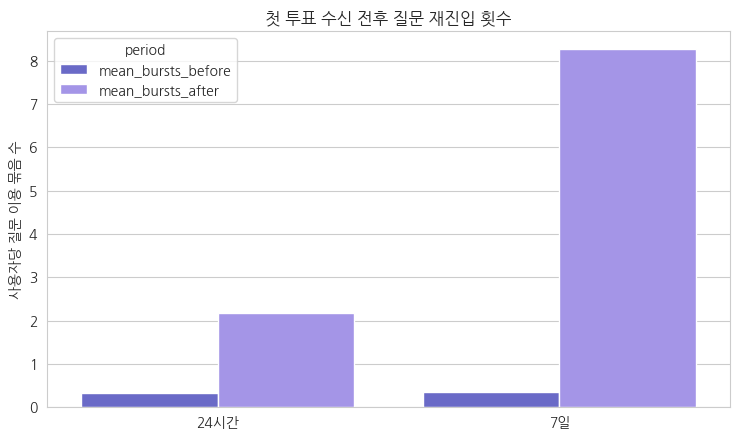

첫 수신 뒤 질문 이용이 늘었다. 수신 시점에 가입과 친구 연결도 겹칠 수 있다.

In [ ]:
# 첫 투표 수신 전후 질문 이용 묶음 비교
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    vote_event_study = con.execute("\n    WITH r AS (\n      SELECT chosen_user_id user_id,MIN(vote_at) first_received_at,COUNT(*) received_votes\n      FROM vote_may WHERE eligible_vote_flag=1 AND chosen_user_id IS NOT NULL GROUP BY 1\n    ), eligible_r AS (\n      SELECT * FROM r WHERE first_received_at>=TIMESTAMP '2023-05-05' AND first_received_at<TIMESTAMP '2023-05-25'\n    )\n    SELECT r.user_id,r.first_received_at,r.received_votes,\n      SUM(CASE WHEN b.burst_start>=r.first_received_at-INTERVAL 7 DAY AND b.burst_start<r.first_received_at THEN 1 ELSE 0 END) bursts_before_7d,\n      SUM(CASE WHEN b.burst_start>r.first_received_at AND b.burst_start<=r.first_received_at+INTERVAL 7 DAY THEN 1 ELSE 0 END) bursts_after_7d,\n      SUM(CASE WHEN b.burst_start>=r.first_received_at-INTERVAL 24 HOUR AND b.burst_start<r.first_received_at THEN 1 ELSE 0 END) bursts_before_24h,\n      SUM(CASE WHEN b.burst_start>r.first_received_at AND b.burst_start<=r.first_received_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END) bursts_after_24h\n    FROM eligible_r r LEFT JOIN qset_burst_summary_all b ON b.owner_user_id=r.user_id\n    GROUP BY ALL\n    ").df()
    paired = []
    for before, after, window in [('bursts_before_24h', 'bursts_after_24h', '24시간'), ('bursts_before_7d', 'bursts_after_7d', '7일')]:
        nz = vote_event_study[before] != vote_event_study[after]
        stat, p = stats.wilcoxon(vote_event_study.loc[nz, before], vote_event_study.loc[nz, after]) if nz.any() else (np.nan, np.nan)
        paired.append([window, len(vote_event_study), vote_event_study[before].mean(), vote_event_study[after].mean(), (vote_event_study[after] > 0).mean() - (vote_event_study[before] > 0).mean(), stat, p])
    vote_event_summary = pd.DataFrame(paired, columns=['window', 'recipients', 'mean_bursts_before', 'mean_bursts_after', 'active_share_difference', 'wilcoxon_stat', 'p_value'])
    display(save_table(vote_event_summary, '67_first_vote_received_event_study'))
    evt = vote_event_summary.melt(id_vars='window', value_vars=['mean_bursts_before', 'mean_bursts_after'], var_name='period', value_name='mean_bursts')
    plt.figure(figsize=(7.5, 4.5))
    sns.barplot(data=evt, x='window', y='mean_bursts', hue='period', palette=COLORS[:2])
    plt.ylabel('사용자당 질문 이용 묶음 수')
    plt.xlabel('')
    plt.title('첫 투표 수신 전후 질문 재진입 횟수')
    savefig('53_vote_received_event_study')
    display(Markdown('첫 수신 뒤 질문 이용이 늘었다. 수신 시점에 가입과 친구 연결도 겹칠 수 있다.'))


- 첫 투표 수신 후 7일의 질문 이용 묶음 수는 평균 8.27회로, 수신 전 7일의 0.35회보다 많았다.
- 가입·학교 내 확산·친구 연결이 비슷한 시기에 일어나 수신만의 영향을 떼어 내기는 어렵다.


### 3-4-6. 질문 완료 직후의 행동과 이동 시간

- 완료와 스킵이 함께 나온 방문, 완료 뒤 첫 이동, 단계별 소요 시간을 살펴봤다. 방문 경로·활동량·앱 버전에 따라 결과가 달라지는지도 비교했다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,outcome_type,visits,notice_after_complete,share
0,스킵만,11815,0.0001,0.0585
1,완료·스킵 모두,98050,0.0893,0.4852
2,완료·스킵 없음,41240,0.0002,0.2041
3,완료만,50967,0.1119,0.2522


/tmp/ipykernel_804/1025752851.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=outcome_summary, x='outcome_type', y='share', palette=COLORS[:len(outcome_summary)])


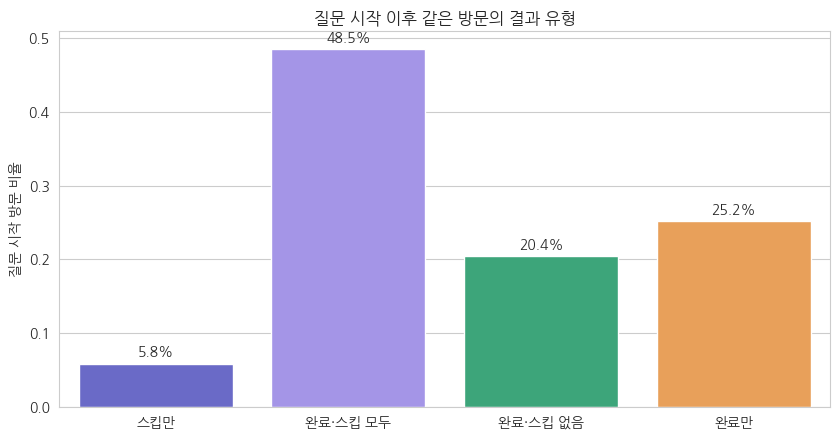

한 방문에서 여러 질문을 풀면 완료와 스킵이 함께 나올 수 있다. 질문 ID로 사건을 연결할 수 없어 방문 단위로 집계했다.

In [ ]:
# 질문 시작 이후 완료·스킵 조합
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    question_outcomes = con.execute("\n    WITH m AS (\n      SELECT visit_id,\n        MIN(event_order) FILTER(WHERE category='03_질문시작') start_order,\n        MIN(event_order) FILTER(WHERE category='05_질문완료') complete_order,\n        MIN(event_order) FILTER(WHERE category='06_질문스킵') skip_order,\n        MIN(event_order) FILTER(WHERE category='07_알림센터') alarm_order,\n        MIN(event_order) FILTER(WHERE category='08_알림상세') notice_order\n      FROM hackle_event_labeled GROUP BY 1\n    )\n    SELECT *,\n      CASE WHEN complete_order>start_order THEN 1 ELSE 0 END complete_after_start,\n      CASE WHEN skip_order>start_order THEN 1 ELSE 0 END skip_after_start,\n      CASE WHEN complete_order>start_order AND skip_order>start_order THEN '완료·스킵 모두'\n           WHEN complete_order>start_order THEN '완료만'\n           WHEN skip_order>start_order THEN '스킵만'\n           ELSE '완료·스킵 없음' END outcome_type,\n      CASE WHEN complete_order IS NOT NULL AND notice_order>complete_order THEN 1 ELSE 0 END notice_after_complete,\n      CASE WHEN complete_order IS NOT NULL AND alarm_order>complete_order THEN 1 ELSE 0 END alarm_after_complete\n    FROM m WHERE start_order IS NOT NULL\n    ").df()
    outcome_summary = question_outcomes.groupby('outcome_type').agg(visits=('visit_id', 'nunique'), notice_after_complete=('notice_after_complete', 'mean')).reset_index()
    outcome_summary['share'] = outcome_summary.visits / outcome_summary.visits.sum()
    display(save_table(outcome_summary, '68_question_start_outcome_types'))
    plt.figure(figsize=(8.5, 4.5))
    ax = sns.barplot(data=outcome_summary, x='outcome_type', y='share', palette=COLORS[:len(outcome_summary)])
    ax.set_ylabel('질문 시작 방문 비율')
    ax.set_xlabel('')
    ax.set_title('질문 시작 이후 같은 방문의 결과 유형')
    for p, v in zip(ax.patches, outcome_summary.share):
        ax.text(p.get_x() + p.get_width() / 2, v + 0.01, f'{v:.1%}', ha='center')
    savefig('54_question_outcome_types')
    display(Markdown('한 방문에서 여러 질문을 풀면 완료와 스킵이 함께 나올 수 있다. 질문 ID로 사건을 연결할 수 없어 방문 단위로 집계했다.'))


- 질문을 시작한 방문의 48.52%에서 완료와 스킵이 모두 나왔다. 스킵이 있는 방문을 모두 미완료로 묶으면 이 방문들의 완료 기록이 빠진다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,transition_name,transition_count,median_seconds,p75_seconds,p90_seconds
0,알림센터→알림상세,127632,3.0000,4.0000,7.0000
1,질문시작→스킵,109485,15.0000,38.0000,72.0000
2,완료→알림센터,17797,16.0000,91.0000,494.0000
3,완료→알림상세,14156,17.0000,90.0000,514.5000
4,진입→질문시작,200717,18.0000,76.0000,254.0000
5,질문시작→완료,148761,75.0000,100.0000,149.0000


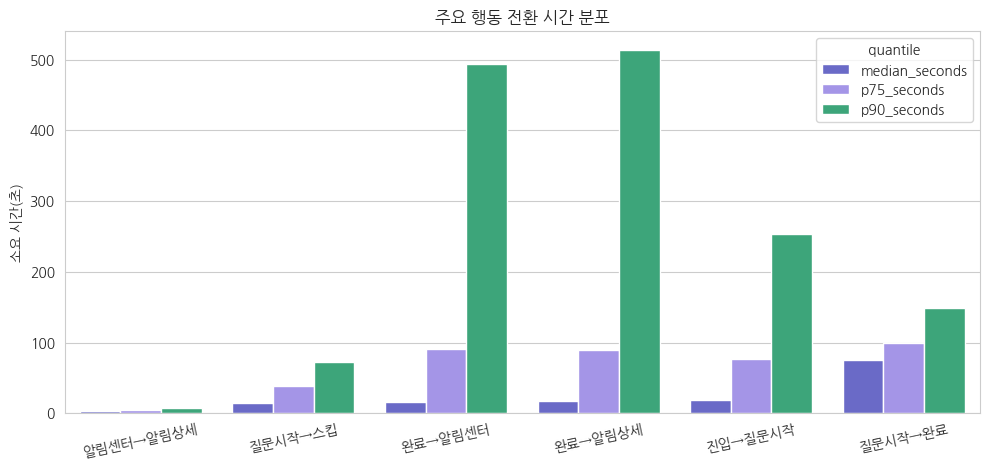

각 방문의 첫 이벤트 사이 시간을 계산했다. 여러 질문을 푼 시간이 섞일 수 있다.

In [ ]:
# 질문·알림 단계 전환시간
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    transition_times = con.execute("\n    WITH firsts AS (\n      SELECT visit_id,\n        MIN(event_at) FILTER(WHERE category='03_질문시작') qstart_at,\n        MIN(event_at) FILTER(WHERE category='05_질문완료') complete_at,\n        MIN(event_at) FILTER(WHERE category='06_질문스킵') skip_at,\n        MIN(event_at) FILTER(WHERE category='07_알림센터') alarm_at,\n        MIN(event_at) FILTER(WHERE category='08_알림상세') notice_at\n      FROM hackle_event_labeled GROUP BY 1\n    ), long AS (\n      SELECT '진입→질문시작' AS transition_name,date_diff('second',v.visit_start,f.qstart_at) AS elapsed_seconds\n      FROM firsts f JOIN hackle_visit_core v USING(visit_id) WHERE f.qstart_at>=v.visit_start\n      UNION ALL SELECT '질문시작→완료',date_diff('second',qstart_at,complete_at) FROM firsts WHERE complete_at>qstart_at\n      UNION ALL SELECT '질문시작→스킵',date_diff('second',qstart_at,skip_at) FROM firsts WHERE skip_at>qstart_at\n      UNION ALL SELECT '완료→알림센터',date_diff('second',complete_at,alarm_at) FROM firsts WHERE alarm_at>complete_at\n      UNION ALL SELECT '완료→알림상세',date_diff('second',complete_at,notice_at) FROM firsts WHERE notice_at>complete_at\n      UNION ALL SELECT '알림센터→알림상세',date_diff('second',alarm_at,notice_at) FROM firsts WHERE notice_at>alarm_at\n    )\n    SELECT transition_name,COUNT(*) transition_count,median(elapsed_seconds) median_seconds,\n           quantile_cont(elapsed_seconds,.75) p75_seconds,quantile_cont(elapsed_seconds,.9) p90_seconds\n    FROM long WHERE elapsed_seconds BETWEEN 0 AND 1800 GROUP BY 1 ORDER BY median_seconds\n    ").df()
    display(save_table(transition_times, '69_interaction_transition_times'))
    tt = transition_times.melt(id_vars=['transition_name', 'transition_count'], value_vars=['median_seconds', 'p75_seconds', 'p90_seconds'], var_name='quantile', value_name='seconds')
    plt.figure(figsize=(10, 4.8))
    sns.barplot(data=tt, x='transition_name', y='seconds', hue='quantile', palette=COLORS[:3])
    plt.ylabel('소요 시간(초)')
    plt.xlabel('')
    plt.xticks(rotation=12)
    plt.title('주요 행동 전환 시간 분포')
    savefig('55_interaction_transition_times')
    display(Markdown('각 방문의 첫 이벤트 사이 시간을 계산했다. 여러 질문을 푼 시간이 섞일 수 있다.'))


- 실제 전환한 방문에서 질문 시작→완료의 소요 시간 중앙값은 75초, 알림센터→상세는 3초였다.
- 이동하지 않은 방문의 어려움은 이 시간 집계에 드러나지 않는다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,next_action,visits,action_share
0,EXIT,39308,0.2618
1,09_타임라인,27358,0.1822
2,04_질문상호작용,21095,0.1405
3,06_질문스킵,14267,0.0950
4,10_랩,11362,0.0757
5,02_질문화면,8032,0.0535
6,07_알림센터,8005,0.0533
7,11_프로필,7455,0.0497
8,13_대화,5673,0.0378
9,01_진입,5159,0.0344


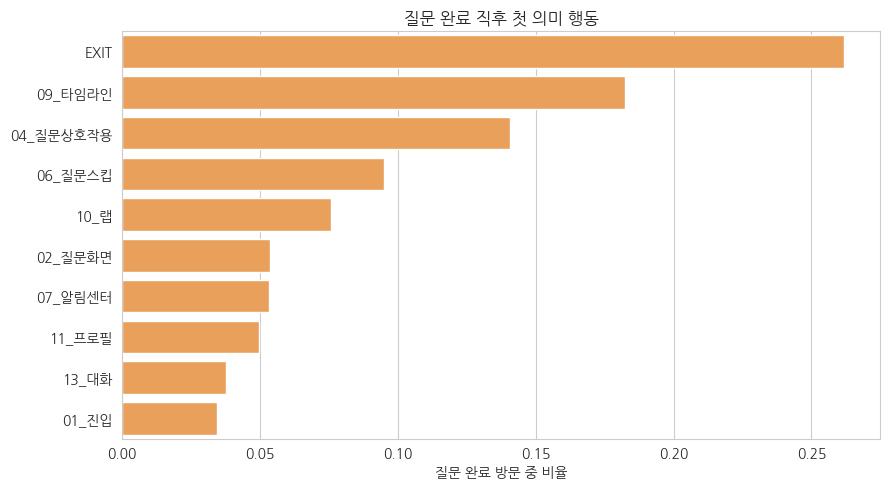

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,notice_visits,later_question_start_rate,later_question_complete_rate,later_friend_action_rate
0,129925,0.2210,0.1603,0.0752


In [ ]:
# 질문 완료 직후 이동 · 알림 상세 이후 행동
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    post_complete = con.execute("\n    WITH c AS (\n      SELECT visit_id,MIN(event_order) complete_order FROM hackle_event_labeled\n      WHERE category='05_질문완료' GROUP BY 1\n    ), afters AS (\n      SELECT e.visit_id,e.category,e.event_order,\n             ROW_NUMBER() OVER(PARTITION BY e.visit_id ORDER BY e.event_order,e.event_sk) rn\n      FROM c JOIN hackle_event_labeled e USING(visit_id)\n      WHERE e.event_order>c.complete_order AND e.category NOT IN ('98_세션종료','99_기타')\n    )\n    SELECT COALESCE(a.category,'EXIT') next_action,COUNT(*) visits,\n           COUNT(*)/SUM(COUNT(*)) OVER() action_share\n    FROM c LEFT JOIN afters a ON a.visit_id=c.visit_id AND a.rn=1\n    GROUP BY 1 ORDER BY visits DESC\n    ").df()
    display(save_table(post_complete, '70_first_action_after_complete'))
    plt.figure(figsize=(9, 5))
    top = post_complete.head(10)
    sns.barplot(data=top, y='next_action', x='action_share', color=COLORS[3])
    plt.xlabel('질문 완료 방문 중 비율')
    plt.ylabel('')
    plt.title('질문 완료 직후 첫 의미 행동')
    savefig('56_first_action_after_complete')
    post_notice = con.execute("\n    WITH n AS (\n      SELECT visit_id,MIN(event_order) notice_order FROM hackle_event_labeled WHERE category='08_알림상세' GROUP BY 1\n    )\n    SELECT COUNT(*) notice_visits,\n      AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='03_질문시작') AS INTEGER)) later_question_start_rate,\n      AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='05_질문완료') AS INTEGER)) later_question_complete_rate,\n      AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='12_친구행동') AS INTEGER)) later_friend_action_rate\n    FROM n\n    ").df()
    display(save_table(post_notice, '71_action_after_notice_detail'))


- 첫 완료 이후 분류 가능한 다음 행동이 없는 방문은 26.18%, 다음 행동이 타임라인인 방문은 18.22%였다. 전자는 실제 앱 종료율과 다르다.
- 알림 상세가 있는 방문 중 이후 질문 시작이 관측된 비율은 22.10%였다. 두 표는 기준 행동과 분모가 다르다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,path_text,users,revisit_7d,ci_low,ci_high
0,01_진입,33558,0.5948,0.5896,0.6001
1,01_진입 → 04_질문상호작용,3179,0.5030,0.4856,0.5204
2,01_진입 → 09_타임라인 → 10_랩 → 11_프로필 → 10_랩,1674,0.4229,0.3995,0.4468
3,01_진입 → 02_질문화면 → 09_타임라인 → 10_랩 → 11_프로필,1615,0.3406,0.3178,0.3640
4,01_진입 → 07_알림센터 → 08_알림상세,1293,0.4470,0.4201,0.4742
5,01_진입 → 02_질문화면,1102,0.3739,0.3458,0.4028
6,01_진입 → 02_질문화면 → 09_타임라인 → 02_질문화면 → 09_타임라인,933,0.3065,0.2778,0.3369
7,01_진입 → 04_질문상호작용 → 09_타임라인 → 10_랩 → 11_프로필,810,0.4432,0.4093,0.4776
8,01_진입 → 09_타임라인 → 10_랩 → 11_프로필,794,0.3829,0.3497,0.4172
9,01_진입 → 09_타임라인 → 02_질문화면 → 10_랩 → 11_프로필,719,0.4381,0.4023,0.4746


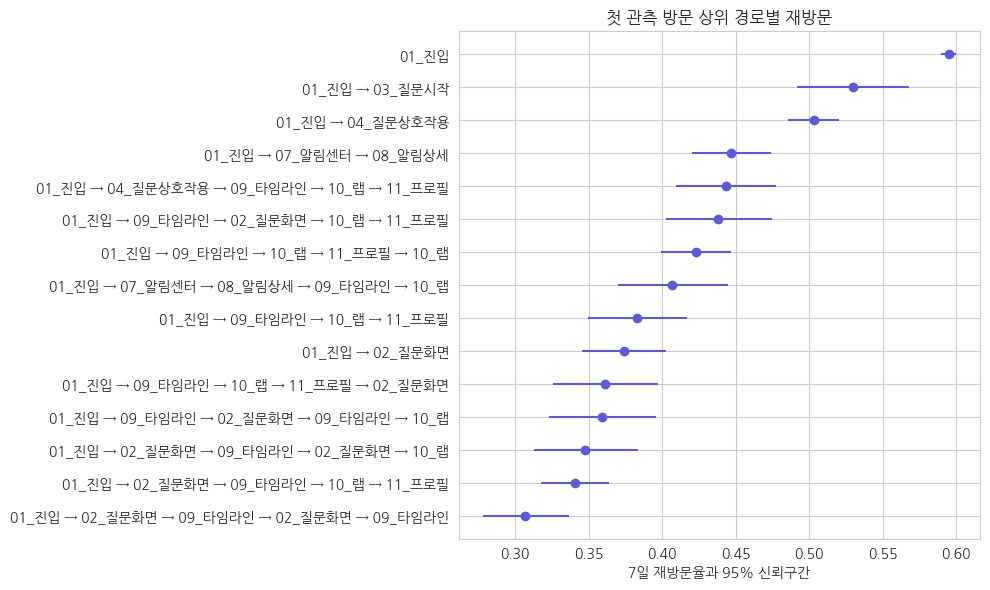

In [ ]:
# 첫 방문 주요 경로 · 7일 재방문 신뢰구간
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    path_revisit = con.execute("\n    WITH iv AS (\n      SELECT *,ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) rn,\n             LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit\n      FROM hackle_visit_core\n      WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0\n    ), firstv AS (SELECT * FROM iv WHERE rn=1), raw AS (\n      SELECT e.visit_id,e.event_order,e.category,\n             LAG(e.category) OVER(PARTITION BY e.visit_id ORDER BY e.event_order,e.event_sk) prev_cat\n      FROM hackle_event_labeled e JOIN firstv f USING(visit_id)\n      WHERE e.category NOT IN ('98_세션종료','99_기타')\n    ), collapsed AS (\n      SELECT *,ROW_NUMBER() OVER(PARTITION BY visit_id ORDER BY event_order) seq\n      FROM raw WHERE prev_cat IS NULL OR category<>prev_cat\n    ), paths AS (\n      SELECT visit_id,STRING_AGG(category,' → ' ORDER BY seq) FILTER(WHERE seq<=5) path_text\n      FROM collapsed GROUP BY 1\n    )\n    SELECT p.path_text,COUNT(*) users,\n           AVG(CASE WHEN f.next_visit<=f.visit_start+INTERVAL 7 DAY THEN 1 ELSE 0 END) revisit_7d\n    FROM paths p JOIN firstv f USING(visit_id)\n    WHERE f.visit_start<=(SELECT MAX(visit_start)-INTERVAL 7 DAY FROM hackle_visit_core)\n    GROUP BY 1 HAVING COUNT(*)>=200 ORDER BY users DESC LIMIT 25\n    ").df()
    z = 1.96
    n = path_revisit.users
    ph = path_revisit.revisit_7d
    den = 1 + z * z / n
    center = (ph + z * z / (2 * n)) / den
    half = z * np.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / den
    path_revisit['ci_low'] = center - half
    path_revisit['ci_high'] = center + half
    display(save_table(path_revisit, '72_first_visit_paths_revisit'))
    plt.figure(figsize=(10, 6))
    top = path_revisit.head(15).sort_values('revisit_7d')
    plt.errorbar(top.revisit_7d, range(len(top)), xerr=[top.revisit_7d - top.ci_low, top.ci_high - top.revisit_7d], fmt='o', color=COLORS[0])
    plt.yticks(range(len(top)), top.path_text)
    plt.xlabel('7일 재방문율과 95% 신뢰구간')
    plt.title('첫 관측 방문 상위 경로별 재방문')
    savefig('57_first_visit_paths_revisit')


- 첫 방문에 진입만 기록된 그룹의 7일 재방문율은 59.48%다.
- 기록이 짧은 경로에는 이벤트 누락과 방문 분리 방식의 영향이 있을 수 있다.


,event_depth_q,not_complete,complete,n_not_complete,n_complete,pp_difference
0,Q1,0.5678,1.0000,23480,4,0.4322
1,Q2,0.5464,0.6294,22858,626,0.0830
2,Q3,0.4296,0.6389,20823,2661,0.2093
3,Q4,0.3799,0.6132,19756,3728,0.2333
4,Q5,0.4089,0.6022,16742,6742,0.1933


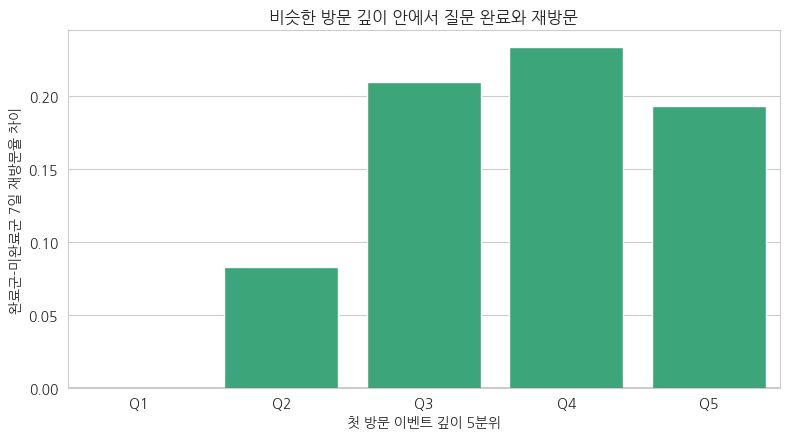

/usr/local/lib/python3.13/dist-packages/statsmodels/formula/formulatools.py:70: FutureWarning: EvalEnvironment is deprecated and support be removed in a future version. You can
pass variables using a dict[str, value] where str is the variable name and the
value is the array of values.

  result = mgr.get_matrices(


,feature,coef,odds_ratio,ci_low,ci_high,p_value
question_complete_flag,question_complete_flag,0.1897,1.2088,1.1410,1.2807,0.0000
question_skip_flag,question_skip_flag,-0.0983,0.9064,0.8513,0.9651,0.0022
question_surface_flag,question_surface_flag,-0.7407,0.4768,0.4583,0.4960,0.0000
alarm_center_flag,alarm_center_flag,-0.8111,0.4444,0.4249,0.4647,0.0000
notice_detail_flag,notice_detail_flag,0.0429,1.0439,0.9951,1.0951,0.0788
browse_flag,browse_flag,-0.7972,0.4506,0.4314,0.4706,0.0000
friend_flag,friend_flag,0.1629,1.1770,1.1097,1.2484,0.0000
chat_flag,chat_flag,-0.0864,0.9172,0.8831,0.9526,0.0000
log_events,log_events,-0.6232,0.5362,0.5102,0.5637,0.0000
log_duration,log_duration,0.2987,1.3481,1.3334,1.3630,0.0000


방문 깊이를 나누고 회귀모형을 적용해 활동량 차이를 줄였다.

In [ ]:
# 방문 깊이별 완료 비교 · 보정 모형
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    adj = revisit_cohort.copy()
    adj['event_depth_q'] = pd.qcut(adj.event_count.rank(method='first'), 5, labels=['Q1', 'Q2', 'Q3', 'Q4', 'Q5'])
    depth_effect = adj.groupby(['event_depth_q', 'question_complete_flag'], observed=True).agg(users=('user_id', 'nunique'), revisit_7d=('next_7d', 'mean'), median_events=('event_count', 'median')).reset_index()
    depth_pivot = depth_effect.pivot(index='event_depth_q', columns='question_complete_flag', values='revisit_7d').reset_index()
    depth_pivot.columns = ['event_depth_q', 'not_complete', 'complete']
    depth_n = depth_effect.pivot(index='event_depth_q', columns='question_complete_flag', values='users').reset_index()
    depth_n.columns = ['event_depth_q', 'n_not_complete', 'n_complete']
    depth_pivot = depth_pivot.merge(depth_n, on='event_depth_q', how='left')
    depth_pivot['pp_difference'] = depth_pivot.complete - depth_pivot.not_complete
    display(save_table(depth_pivot, '73_depth_stratified_completion_revisit'))
    depth_plot = depth_pivot[(depth_pivot.n_complete >= 100) & (depth_pivot.n_not_complete >= 100)].copy()
    plt.figure(figsize=(8, 4.5))
    ax = sns.barplot(data=depth_plot, x='event_depth_q', y='pp_difference', color=COLORS[2])
    plt.axhline(0, color='black', lw=1)
    plt.ylabel('완료군-미완료군 7일 재방문율 차이')
    plt.xlabel('첫 방문 이벤트 깊이 5분위')
    plt.title('비슷한 방문 깊이 안에서 질문 완료와 재방문')
    savefig('58_depth_stratified_completion_revisit')
    adj['log_events'] = np.log1p(adj.event_count)
    adj['log_duration'] = np.log1p(adj.duration_seconds.clip(lower=0))
    formula = 'next_7d ~ question_complete_flag + question_skip_flag + question_surface_flag + alarm_center_flag + notice_detail_flag + browse_flag + friend_flag + chat_flag + log_events + log_duration + distinct_event_count'
    afit = smf.glm(formula, data=adj, family=sm.families.Binomial(), eval_env=-1).fit(cov_type='HC3')
    keep = ['question_complete_flag', 'question_skip_flag', 'question_surface_flag', 'alarm_center_flag', 'notice_detail_flag', 'browse_flag', 'friend_flag', 'chat_flag', 'log_events', 'log_duration', 'distinct_event_count']
    adjusted = pd.DataFrame({'feature': keep, 'coef': afit.params[keep], 'odds_ratio': np.exp(afit.params[keep]), 'ci_low': np.exp(afit.conf_int().loc[keep, 0]), 'ci_high': np.exp(afit.conf_int().loc[keep, 1]), 'p_value': afit.pvalues[keep]})
    display(save_table(adjusted, '74_adjusted_revisit_associations'))
    display(Markdown('방문 깊이를 나누고 회귀모형을 적용해 활동량 차이를 줄였다.'))


- 활동량 구간별 비교에서 완료군의 재방문율이 더 높다. 표본이 적은 구간의 차이는 특히 주의한다.
- 조건을 함께 넣은 모형에서 질문 완료의 오즈비는 1.2088이다. 관측 조건을 보정한 연관이며 인과효과는 아니다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,app_version,visits,question_start_rate,complete_after_start_all_visit_rate,complete_given_start,notice_given_complete
0,MISSING,590419,0.2466,0.1913,0.7757,0.0940
1,2.0.5,253301,0.1983,0.1280,0.6451,0.1066
2,2.0.3,41926,0.1490,0.0878,0.5892,0.1160


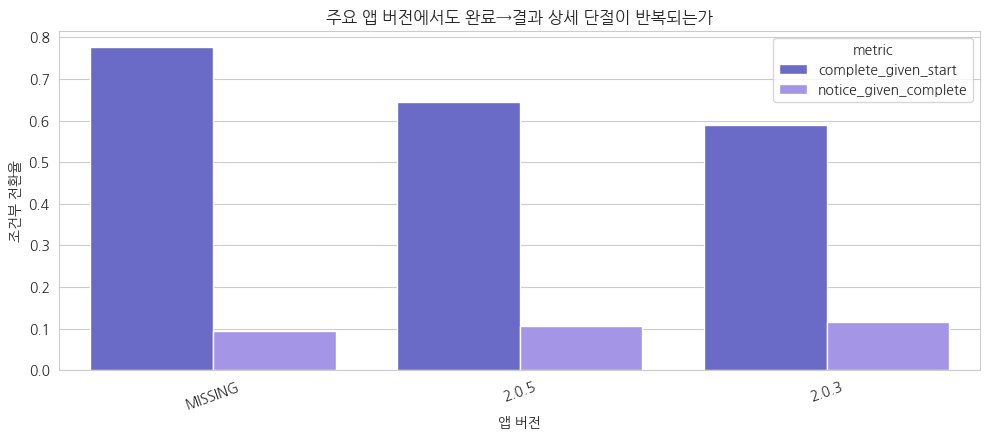

In [ ]:
# 앱 버전별 질문 완료·알림 연결
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    version_flow = con.execute("\n    WITH o AS (\n      SELECT visit_id,\n        MIN(event_order) FILTER(WHERE category='03_질문시작') s,\n        MIN(event_order) FILTER(WHERE category='05_질문완료') c,\n        MIN(event_order) FILTER(WHERE category='08_알림상세') n\n      FROM hackle_event_labeled GROUP BY 1\n    )\n    SELECT COALESCE(v.app_version,'MISSING') app_version,COUNT(*) visits,\n      AVG(CASE WHEN o.s IS NOT NULL THEN 1 ELSE 0 END) question_start_rate,\n      AVG(CASE WHEN o.c>o.s THEN 1 ELSE 0 END) complete_after_start_all_visit_rate,\n      AVG(CASE WHEN o.s IS NOT NULL THEN CASE WHEN o.c>o.s THEN 1 ELSE 0 END END) complete_given_start,\n      AVG(CASE WHEN o.c IS NOT NULL THEN CASE WHEN o.n>o.c THEN 1 ELSE 0 END END) notice_given_complete\n    FROM hackle_visit_core v JOIN o USING(visit_id)\n    GROUP BY 1 HAVING COUNT(*)>=10000 ORDER BY visits DESC\n    ").df()
    display(save_table(version_flow, '75_app_version_flow_robustness'))
    vv = version_flow.melt(id_vars=['app_version', 'visits'], value_vars=['complete_given_start', 'notice_given_complete'], var_name='metric', value_name='rate')
    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=vv, x='app_version', y='rate', hue='metric', palette=COLORS[:2])
    plt.ylabel('조건부 전환율')
    plt.xlabel('앱 버전')
    plt.xticks(rotation=20)
    plt.title('주요 앱 버전에서도 완료→결과 상세 단절이 반복되는가')
    savefig('59_app_version_flow_robustness')


- 시작 후 완료 비율은 앱 2.0.5에서 64.51%, 2.0.3에서 58.92%다. 완료 뒤 알림 상세 도달은 각각 10.66%·11.60%다.
- 버전 누락군과 버전별 사용자 구성이 달라 버전 변경 효과로 해석하지 않는다.


In [ ]:
# 완료 기록·재진입·후속 경로 결과 정리
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    true_return_7d = float(first_may_day.next_active_day_7d.mean())
    same_burst = float((first_next.hours_to_next <= 0.5).mean())
    struct_loss = float(loss.structurally_incomplete_sets.iloc[0] / loss.total_sets.iloc[0])
    behavior_complete = float(loss.behavior_completion_rate_given_structure.iloc[0])
    complete_or = float(adjusted.loc[adjusted.feature.eq('question_complete_flag'), 'odds_ratio'].iloc[0])
    notice_after = float(post_notice.later_question_start_rate.iloc[0])
    advanced_evidence = pd.DataFrame([['완료율 분해', f'현재 DB에서 10개 미만 연결 {struct_loss:.1%}; 10개 연결 세트의 투표 완료 {behavior_complete:.1%}', '사용자 이탈 결론 보류, 원천 참조 무결성과 실제 노출 로그 우선 확인'], ['연속 소비와 재진입 분리', f'첫 세트 다음 행동 중 같은 30분 묶음 {same_burst:.1%}; 7일 내 다음 활성일 {true_return_7d:.1%}', '같은 날 자동 연속과 다른 날 재방문 KPI를 분리'], ['Content→Interaction', f'보정 후 종합 소진·신규성은 다음 활성일 감소의 유의한 근거 없음', '빈도 제한·다양성 슬롯은 확정안이 아니라 A/B 테스트 가설로 유지'], ['선택받음 루프', '첫 투표 수신 전후 질문 묶음 변화는 시간순 근거이나 비무작위', '투표 수신 알림→결과→반응 이벤트를 새로 계측'], ['완료 후 단절', f'알림 상세 후 같은 방문 질문 재시작 {notice_after:.1%}', '결과 상세에 다음 질문·되묻기·반응 CTA 배치'], ['재방문 연관 강건성', f'활동 깊이 등을 보정한 질문 완료 OR {complete_or:.2f}', '완료 자체보다 완료 뒤 가치 경험을 A/B 테스트'], ['계측 재설계', 'open_ping 0건으로 직접 Ping 루프 검증 불가', 'impression→vote/skip→result→reaction→next_content 공통 키 저장']], columns=['evidence_block', 'result', 'product_decision'])
    display(save_table(advanced_evidence, '76_advanced_evidence_to_product'))
    advanced_qa = pd.DataFrame([['기존 셀 보존 후 추가', True, 'F 절부터 신규 셀'], ['5월 완료 DB 참조·행동 손실 분해', True, 'expected·mapped·voted pieces 분리, 실제 노출 결론 보류'], ['같은 30분 묶음과 재진입 분리', True, '질문세트 30분 gap sessionization'], ['Content 지표를 실제 재진입과 연결', True, '7일 내 다음 활성일 + 사용자 cluster SE'], ['투표 수신 시간순 분석', True, '첫 수신 전후 동일 사용자'], ['질문 시작 결과 상호배타 분류', True, '완료만·스킵만·둘 다·둘 다 없음'], ['행동 전환시간', True, '30분 방문 안 0~1800초'], ['완료·알림 이후 다음 행동', True, '실제 event_order 사용'], ['경로별 재방문 신뢰구간', True, '상위 first-visit collapsed path'], ['방문 깊이 강건성', True, '5분위 층화 + HC3 회귀'], ['앱 버전 강건성', True, '1만 방문 이상 버전'], ['인과 경계 명시', True, '관찰 연관과 실험 제안 분리']], columns=['check', 'pass', 'evidence'])
    display(save_table(advanced_qa, '77_advanced_final_qa'))
    assert advanced_qa['pass'].all()
    print(f"ADVANCED QA: PASS {advanced_qa['pass'].sum()} / FAIL 0")
team7_release_unused('345', 'Interaction 전환 분석 완료')


,evidence_block,result,product_decision
0,완료율 분해,현재 DB에서 10개 미만 연결 64.8%; 10개 연결 세트의 투표 완료 94.2%,"사용자 이탈 결론 보류, 원천 참조 무결성과 실제 노출 로그 우선 확인"
1,연속 소비와 재진입 분리,첫 세트 다음 행동 중 같은 30분 묶음 65.7%; 7일 내 다음 활성일 94.1%,같은 날 자동 연속과 다른 날 재방문 KPI를 분리
2,Content→Interaction,보정 후 종합 소진·신규성은 다음 활성일 감소의 유의한 근거 없음,빈도 제한·다양성 슬롯은 확정안이 아니라 A/B 테스트 가설로 유지
3,선택받음 루프,첫 투표 수신 전후 질문 묶음 변화는 시간순 근거이나 비무작위,투표 수신 알림→결과→반응 이벤트를 새로 계측
4,완료 후 단절,알림 상세 후 같은 방문 질문 재시작 22.1%,결과 상세에 다음 질문·되묻기·반응 CTA 배치
5,재방문 연관 강건성,활동 깊이 등을 보정한 질문 완료 OR 1.21,완료 자체보다 완료 뒤 가치 경험을 A/B 테스트
6,계측 재설계,open_ping 0건으로 직접 Ping 루프 검증 불가,impression→vote/skip→result→reaction→next_cont...


,check,pass,evidence
0,기존 셀 보존 후 추가,True,F 절부터 신규 셀
1,5월 완료 DB 참조·행동 손실 분해,True,"expected·mapped·voted pieces 분리, 실제 노출 결론 보류"
2,같은 30분 묶음과 재진입 분리,True,질문세트 30분 gap sessionization
3,Content 지표를 실제 재진입과 연결,True,7일 내 다음 활성일 + 사용자 cluster SE
4,투표 수신 시간순 분석,True,첫 수신 전후 동일 사용자
5,질문 시작 결과 상호배타 분류,True,완료만·스킵만·둘 다·둘 다 없음
6,행동 전환시간,True,30분 방문 안 0~1800초
7,완료·알림 이후 다음 행동,True,실제 event_order 사용
8,경로별 재방문 신뢰구간,True,상위 first-visit collapsed path
9,방문 깊이 강건성,True,5분위 층화 + HC3 회귀


ADVANCED QA: PASS 12 / FAIL 0
[Interaction 전환 분석 완료] 사용이 끝난 변수 54개 정리
[Interaction 전환 분석 완료] Python 사용 RAM 3.61 GB / 시스템 여유 RAM 8.58 GB


- 5월 DB의 완료 대리지표 33.15%에는 질문조각 연결 부족이, 다음 세트 생성률 97.03%에는 같은 방문의 연속 이용이 섞여 있었다.
- 별도 자료인 7~8월 로그에서는 완료 이후 알림 상세·공유·다음 질문으로 이어지는 경로를 살펴봤다.


### 3-4-7. 완료 이후 공유·관계 행동의 연결

- 같은 방문에서 시작보다 뒤에 나온 완료, 완료보다 뒤에 나온 행동을 연결했다. 첫 이벤트만 보던 앞선 집계와 달리 반복 행동도 반영했다.
- 재방문뿐 아니라 다음 질문 완료와 친구 행동도 살펴봤다. 완료 후 행동은 한 방문에서 겹칠 수 있으므로 비율의 합이 100%가 될 필요는 없다.


In [ ]:
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    # 질문 시작 이후의 완료와 완료 이후 행동을 실제 event_order로 다시 구성한다.
    # 공유는 click_question_share 이벤트로 별도 집계한다.
    con.execute("""
    CREATE OR REPLACE TEMP TABLE visit_order_final_v2 AS
    WITH starts AS (
      SELECT visit_id,
             MIN(event_order) FILTER(WHERE category='03_질문시작') qstart_order,
             MIN(event_at) FILTER(WHERE category='03_질문시작') qstart_at,
             MIN(event_order) FILTER(WHERE event_key='click_question_share') first_share_order
      FROM hackle_event_labeled GROUP BY 1
    ), ordered AS (
      SELECT s.visit_id,s.qstart_order,s.qstart_at,s.first_share_order,
             MIN(e.event_order) FILTER(WHERE e.category='05_질문완료' AND e.event_order>s.qstart_order) qcomplete_order,
             MIN(e.event_at) FILTER(WHERE e.category='05_질문완료' AND e.event_order>s.qstart_order) qcomplete_at,
             MIN(e.event_order) FILTER(WHERE e.category='06_질문스킵' AND e.event_order>s.qstart_order) qskip_order
      FROM starts s JOIN hackle_event_labeled e USING(visit_id)
      GROUP BY ALL
    )
    SELECT o.*,
           COUNT(*) FILTER(WHERE e.event_order<o.qstart_order) prestart_event_count,
           COUNT(DISTINCT e.category) FILTER(WHERE e.event_order<o.qstart_order AND e.category<>'99_기타') prestart_category_count,
           MAX(CASE WHEN e.event_order<o.qstart_order AND e.category IN ('09_타임라인','10_랩','11_프로필') THEN 1 ELSE 0 END) prestart_browse,
           MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='07_알림센터' THEN 1 ELSE 0 END) prestart_alarm,
           MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='08_알림상세' THEN 1 ELSE 0 END) prestart_notice,
           MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='12_친구행동' THEN 1 ELSE 0 END) prestart_friend,
           MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='13_대화' THEN 1 ELSE 0 END) prestart_chat,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='07_알림센터' THEN 1 ELSE 0 END) alarm_after_complete,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='08_알림상세' THEN 1 ELSE 0 END) notice_after_complete,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.event_key='click_question_share' THEN 1 ELSE 0 END) share_after_complete,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='03_질문시작' THEN 1 ELSE 0 END) qstart_after_complete,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='12_친구행동' THEN 1 ELSE 0 END) friend_after_complete,
           MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='13_대화' THEN 1 ELSE 0 END) chat_after_complete,
           COUNT(*) FILTER(WHERE e.event_order>o.qcomplete_order) postcomplete_event_count,
           arg_min(e.friend_count,e.event_order) initial_friend_count,
           arg_min(e.votes_count,e.event_order) initial_votes_count
    FROM ordered o JOIN hackle_event_labeled e USING(visit_id)
    GROUP BY ALL
    """)

    con.execute("""
    CREATE OR REPLACE TEMP TABLE first_visit_final_v2 AS
    WITH seq AS (
      SELECT v.*,
             ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) visit_no,
             LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit_start
      FROM hackle_visit_interaction v
      WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL
        AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0
    ), firstv AS (
      SELECT *,
             CASE WHEN next_visit_start<=visit_start+INTERVAL 7 DAY THEN 1 ELSE 0 END revisit_7d
      FROM seq WHERE visit_no=1
        AND visit_start<=(SELECT MAX(visit_start)-INTERVAL 7 DAY FROM hackle_visit_core)
    ), later AS (
      SELECT f.visit_id,
             MAX(n.question_start_flag) next7_question_start,
             MAX(n.question_complete_flag) next7_question_complete,
             MAX(n.notice_detail_flag) next7_notice_detail,
             MAX(n.friend_flag) next7_friend_action,
             MAX(n.chat_flag) next7_chat_action
      FROM firstv f LEFT JOIN hackle_visit_interaction n
        ON n.user_id=f.user_id AND n.visit_start>f.visit_start
       AND n.visit_start<=f.visit_start+INTERVAL 7 DAY
       AND n.identity_status='IDENTIFIED_SERVICE_USER'
       AND COALESCE(n.is_staff,0)=0 AND COALESCE(n.is_superuser,0)=0
      GROUP BY 1
    )
    SELECT f.*,o.* EXCLUDE(visit_id),
           date_diff('second',f.visit_start,o.qstart_at) seconds_to_question_start,
           GREATEST(0,date_diff('day',f.signup_at,f.visit_start)) signup_tenure_days,
           COALESCE(l.next7_question_start,0) next7_question_start,
           COALESCE(l.next7_question_complete,0) next7_question_complete,
           COALESCE(l.next7_notice_detail,0) next7_notice_detail,
           COALESCE(l.next7_friend_action,0) next7_friend_action,
           COALESCE(l.next7_chat_action,0) next7_chat_action
    FROM firstv f JOIN visit_order_final_v2 o USING(visit_id)
    LEFT JOIN later l USING(visit_id)
    """)

    final_scope=con.execute("""
    SELECT COUNT(*) observable_first_visits,
           COUNT(*) FILTER(WHERE qstart_order IS NOT NULL) question_start_first_visits,
           COUNT(*) FILTER(WHERE qcomplete_order IS NOT NULL) ordered_complete_first_visits,
           COUNT(*) FILTER(WHERE share_after_complete=1) share_after_complete_first_visits
    FROM first_visit_final_v2
    """).df()
    display(save_table(final_scope,'80_final_analysis_scope'))


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,observable_first_visits,question_start_first_visits,ordered_complete_first_visits,share_after_complete_first_visits
0,117420,21874,13741,341


- 7일 관찰 가능한 첫 방문 117,420개 중 질문 시작은 21,874개, 시작 이후 완료가 있는 방문은 13,741개였다.
- 질문 미시작부터 완료 이후 행동까지 첫 방문의 참여 단계를 나누어 비교한다.


,transition,numerator,denominator,rate
0,질문 시작→완료,149038,202072,0.7375
1,질문 시작→공유,3747,202072,0.0185
2,완료→공유,4508,149038,0.0302
3,완료→알림센터,24156,149038,0.1621
4,완료→알림상세,18561,149038,0.1245
5,완료→다음 질문,3162,149038,0.0212
6,완료→친구/대화,26813,149038,0.1799


/tmp/ipykernel_804/2575620088.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(data=social_loop,x='transition',y='rate',palette=COLORS+COLORS[:1])


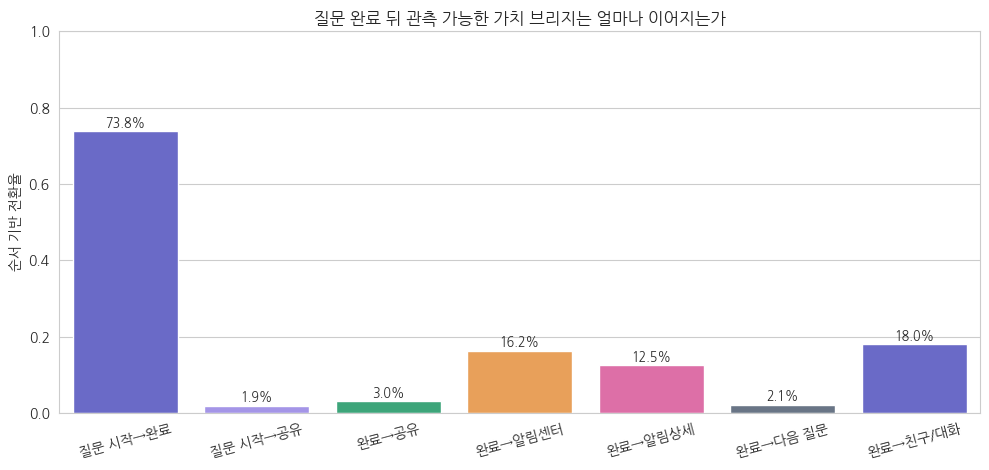

> `click_question_share`를 복원해도 결과·공유·관계 행동은 서로 다른 대리지표다. 공식 `open_ping`이 0건이므로 이 표를 완전한 Ping 가치 루프로 해석하지 않는다.

GitHub 기준: 시작→공유는 방문의 첫 공유가 시작보다 뒤에 있는지를 센다. 완료→공유는 완료 이후 공유가 하나라도 있는지를 센다. 정의가 달라 두 분자는 포함관계가 보장되지 않는다.

In [ ]:
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    social_loop=con.execute("""
    SELECT * FROM (VALUES
      ('질문 시작→완료',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_order IS NOT NULL)),
      ('질문 시작→공유',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE first_share_order>qstart_order),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_order IS NOT NULL)),
      ('완료→공유',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE share_after_complete=1),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
      ('완료→알림센터',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE alarm_after_complete=1),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
      ('완료→알림상세',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE notice_after_complete=1),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
      ('완료→다음 질문',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_after_complete=1),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
      ('완료→친구/대화',
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE friend_after_complete=1 OR chat_after_complete=1),
        (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL))
    ) t(transition,numerator,denominator)
    """).df()
    social_loop['rate']=social_loop.numerator/social_loop.denominator
    display(save_table(social_loop,'81_completion_social_loop'))

    plt.figure(figsize=(10,4.8))
    ax=sns.barplot(data=social_loop,x='transition',y='rate',palette=COLORS+COLORS[:1])
    ax.set_ylim(0,1); ax.set_xlabel(''); ax.set_ylabel('순서 기반 전환율')
    ax.set_title('질문 완료 뒤 관측 가능한 가치 브리지는 얼마나 이어지는가')
    for p,v in zip(ax.patches,social_loop.rate):
        ax.text(p.get_x()+p.get_width()/2,v+.012,f'{v:.1%}',ha='center',fontsize=9)
    plt.xticks(rotation=15); savefig('60_completion_social_loop')
    display(Markdown('> 알림 상세·공유·관계 행동은 서로 다른 대리지표다. `open_ping` 이벤트가 없어 실제 Ping 열람과 반응의 전체 경로는 확인할 수 없다.'))
    display(Markdown("시작→공유는 방문의 첫 공유가 시작보다 뒤에 있는지를 센다. 완료→공유는 완료 이후 공유가 하나라도 있는지를 센다. 정의가 달라 두 분자는 포함관계가 보장되지 않는다."))


- 질문 시작 방문 202,072개 중 완료율은 73.75%, 시작→공유는 1.85%(3,747/202,072)였다.
- 시작 후 완료가 있는 방문 149,038개를 기준으로 알림 상세 12.45%, 공유 3.02%, 다음 질문 2.12%였다. 이 행동들은 서로 겹칠 수 있다.
- 시작→공유는 첫 공유의 순서, 완료→공유는 완료 뒤 공유 유무를 보므로 두 분자의 포함관계는 보장되지 않는다.


,activation_stage,users,revisit_7d,next7_question_start,next7_question_complete,next7_notice_detail,next7_friend_action
0,질문 미시작,95546,0.4782,0.1261,0.0913,0.1249,0.0456
1,시작 후 미완료,8133,0.4235,0.1788,0.1371,0.1084,0.0509
2,완료 후 후속행동 없음,9190,0.6055,0.3874,0.3526,0.2091,0.0782
3,완료+다음 질문,13,0.9231,0.6923,0.6923,0.5385,0.2308
4,완료+결과·공유·관계,4538,0.6276,0.4204,0.3825,0.2358,0.1219


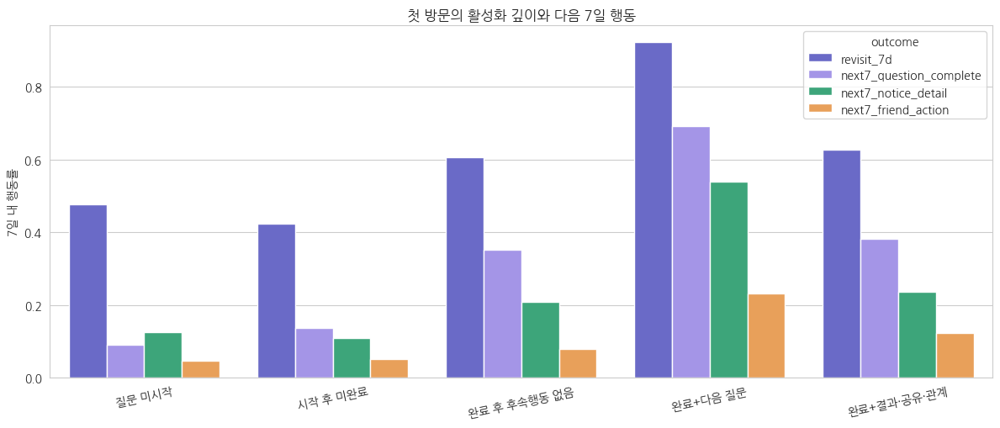

원래 활동적인 사용자가 후속 행동까지 했을 수 있다. 다음 비교에서는 완료 전 조건을 맞췄다.

In [ ]:
# 첫 방문 참여 단계별 다음 7일 행동
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    final_first = con.execute('SELECT * FROM first_visit_final_v2').df()
    final_first['activation_stage'] = np.select([final_first.qstart_order.isna(), final_first.qstart_order.notna() & final_first.qcomplete_order.isna(), final_first.qcomplete_order.notna() & ((final_first.notice_after_complete == 1) | (final_first.alarm_after_complete == 1) | (final_first.share_after_complete == 1) | (final_first.friend_after_complete == 1) | (final_first.chat_after_complete == 1)), final_first.qcomplete_order.notna() & (final_first.qstart_after_complete == 1)], ['질문 미시작', '시작 후 미완료', '완료+결과·공유·관계', '완료+다음 질문'], default='완료 후 후속행동 없음')
    stage_order = ['질문 미시작', '시작 후 미완료', '완료 후 후속행동 없음', '완료+다음 질문', '완료+결과·공유·관계']
    stage_outcomes = final_first.groupby('activation_stage').agg(users=('user_id', 'nunique'), revisit_7d=('revisit_7d', 'mean'), next7_question_start=('next7_question_start', 'mean'), next7_question_complete=('next7_question_complete', 'mean'), next7_notice_detail=('next7_notice_detail', 'mean'), next7_friend_action=('next7_friend_action', 'mean')).reindex(stage_order).reset_index()
    display(save_table(stage_outcomes, '82_activation_stage_next7d_outcomes'))
    stage_long = stage_outcomes.melt(id_vars=['activation_stage', 'users'], value_vars=['revisit_7d', 'next7_question_complete', 'next7_notice_detail', 'next7_friend_action'], var_name='outcome', value_name='rate')
    plt.figure(figsize=(12, 5.2))
    sns.barplot(data=stage_long, x='activation_stage', y='rate', hue='outcome', palette=COLORS[:4])
    plt.xlabel('')
    plt.ylabel('7일 내 행동률')
    plt.xticks(rotation=12)
    plt.title('첫 방문의 활성화 깊이와 다음 7일 행동')
    savefig('61_activation_stage_next7d')
    display(Markdown('원래 활동적인 사용자가 후속 행동까지 했을 수 있다. 다음 비교에서는 완료 전 조건을 맞췄다.'))


- 시작 후 미완료 그룹의 7일 재방문율은 42.35%, 완료 후 지정된 후속 행동이 없는 그룹은 60.55%였다. 후자는 다른 탐색 행동까지 없었다는 뜻은 아니다.
- 완료 후 결과·공유·관계 행동 그룹은 62.76%였다. '완료+다음 질문' 그룹은 다른 후속 행동이 우선 배정된 뒤 남은 13명으로, 전체 다음 질문 참여자와 다르다.


대표 행동은 알림 상세→공유→친구·대화→알림센터→다음 질문 순으로 하나씩 배정했다. 알림 상세 그룹에는 다른 행동을 함께 한 사람도 포함된다. 공유 그룹은 알림 상세 없이 공유한 사람만 포함한다.

,representative_action,users,revisit_7d,next7_question_complete,next7_friend_action,revisit_ci_low,revisit_ci_high
0,기타 이동·종료,9190,0.6055,0.3526,0.0782,0.5955,0.6155
1,다음 질문,13,0.9231,0.6923,0.2308,0.6669,0.9863
2,알림센터(다음 질문 포함 가능),287,0.5331,0.2613,0.0592,0.4753,0.5900
3,알림 상세(다른 행동 포함),1896,0.6013,0.3776,0.1203,0.5790,0.6231
4,알림 상세 없이 공유,224,0.7812,0.5491,0.1384,0.7226,0.8304
5,상세·공유 없이 친구·대화,2131,0.6476,0.3857,0.1300,0.6271,0.6676


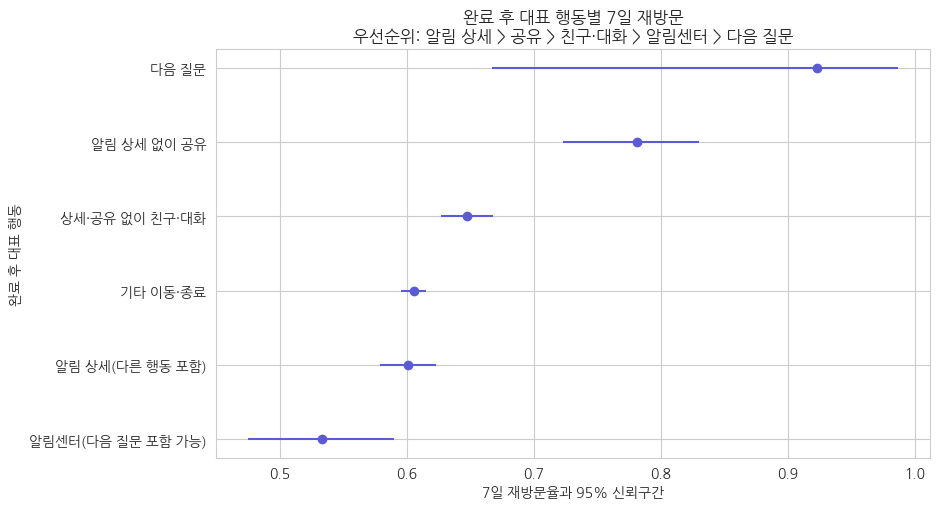

In [ ]:
# 완료 후 대표 행동별 재방문·후속 질문
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    completed_first = final_first[final_first.qcomplete_order.notna()].copy()
    completed_first['postcomplete_route'] = np.select([completed_first.notice_after_complete.eq(1), completed_first.share_after_complete.eq(1), completed_first.friend_after_complete.eq(1) | completed_first.chat_after_complete.eq(1), completed_first.alarm_after_complete.eq(1), completed_first.qstart_after_complete.eq(1)], ['알림 상세(다른 행동 포함)', '알림 상세 없이 공유', '상세·공유 없이 친구·대화', '알림센터(다음 질문 포함 가능)', '다음 질문'], default='기타 이동·종료')
    route_order = ['기타 이동·종료', '다음 질문', '알림센터(다음 질문 포함 가능)', '알림 상세(다른 행동 포함)', '알림 상세 없이 공유', '상세·공유 없이 친구·대화']
    route_summary = completed_first.groupby('postcomplete_route').agg(users=('user_id', 'nunique'), revisit_7d=('revisit_7d', 'mean'), next7_question_complete=('next7_question_complete', 'mean'), next7_friend_action=('next7_friend_action', 'mean')).reindex(route_order).dropna(subset=['users']).reset_index().rename(columns={'postcomplete_route': 'representative_action'})
    z = 1.96
    n = route_summary.users
    p = route_summary.revisit_7d
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    route_summary['revisit_ci_low'] = center - half
    route_summary['revisit_ci_high'] = center + half
    display(Markdown('대표 행동은 알림 상세→공유→친구·대화→알림센터→다음 질문 순으로 하나씩 배정했다. 알림 상세 그룹에는 다른 행동을 함께 한 사람도 포함된다. 공유 그룹은 알림 상세 없이 공유한 사람만 포함한다.'))
    display(save_table(route_summary, '83_postcompletion_route_outcomes'))
    rp = route_summary.sort_values('revisit_7d')
    plt.figure(figsize=(9.5, 5.2))
    plt.errorbar(rp.revisit_7d, range(len(rp)), xerr=[rp.revisit_7d - rp.revisit_ci_low, rp.revisit_ci_high - rp.revisit_7d], fmt='o', color=COLORS[0])
    plt.yticks(range(len(rp)), rp.representative_action)
    plt.xlabel('7일 재방문율과 95% 신뢰구간')
    plt.ylabel('완료 후 대표 행동')
    plt.title('완료 후 대표 행동별 7일 재방문\n우선순위: 알림 상세 > 공유 > 친구·대화 > 알림센터 > 다음 질문')
    savefig('62_postcompletion_route_revisit')


- 알림 상세 없이 공유한 224명의 7일 재방문율은 78.12%다. 전체 완료 후 공유자는 341명이며 상세도 본 사람은 우선순위상 상세 그룹에 포함된다.
- 알림 상세 대표 그룹 1,896명의 재방문율은 60.13%, 기타 이동·종료 그룹은 60.55%다. 대표 행동은 첫 행동이 아니라 우선순위에 따라 배정한 분류다.


### 3-4-8. 완료 전 조건을 맞춘 후속 행동 비교

- 질문을 시작한 첫 관측 방문에서 완료군과 미완료군의 활동량·가입 경과일 등을 가중치로 맞췄다. 완료 이전에 측정한 조건을 사용했으며, 기록에 없는 방문 목적이나 동기 차이는 남아 있다.


,feature,smd_before,smd_after
0,prestart_event_count,0.0201,0.0105
1,prestart_category_count,-0.0438,-0.0054
2,seconds_to_question_start,0.0749,0.0015
3,signup_tenure_days,-0.1608,-0.0313
4,initial_friend_count,0.0089,-0.0081
5,initial_votes_count,0.0157,-0.0065
6,prestart_browse,-0.0424,-0.0043
7,prestart_alarm,0.0176,-0.0008
8,prestart_notice,0.0675,-0.0005
9,prestart_friend,0.0210,0.0012


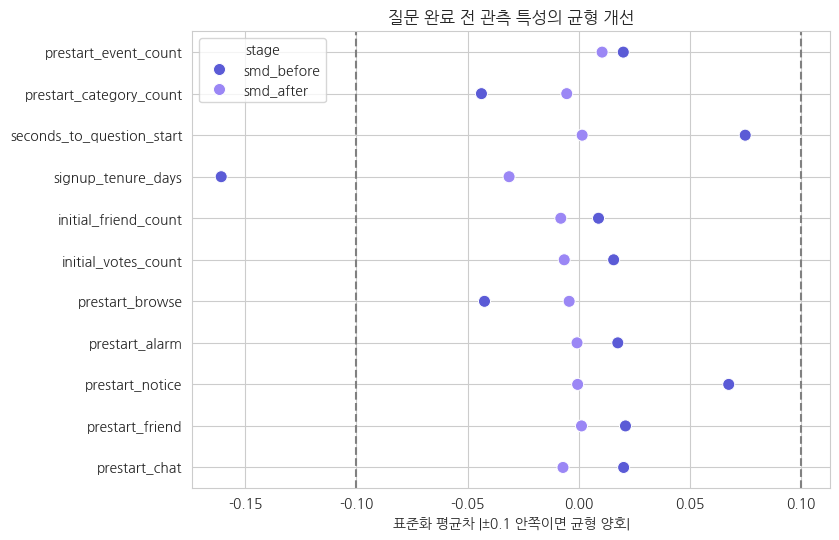

,original_started_visits,common_support_visits,retained_share,completion_rate,propensity_auc,max_abs_smd_before,max_abs_smd_after,effective_sample_size
0,21874,21169,0.9678,0.6261,0.5766,0.1608,0.0313,"20,889.2180"


In [ ]:
# 완료 전 조건의 성향점수 · 가중 후 균형
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    ps = final_first[final_first.qstart_order.notna()].copy()
    ps['completed_after_start'] = ps.qcomplete_order.notna().astype(int)
    ps['seconds_to_question_start'] = ps.seconds_to_question_start.clip(lower=0, upper=1800)
    ps['signup_tenure_days'] = ps.signup_tenure_days.clip(lower=0, upper=3650)
    ps_features = ['prestart_event_count', 'prestart_category_count', 'seconds_to_question_start', 'signup_tenure_days', 'initial_friend_count', 'initial_votes_count', 'prestart_browse', 'prestart_alarm', 'prestart_notice', 'prestart_friend', 'prestart_chat']
    X = ps[ps_features].replace([np.inf, -np.inf], np.nan).copy()
    for c in ps_features:
        X[c] = X[c].fillna(X[c].median() if X[c].notna().any() else 0)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    propensity_model = LogisticRegression(max_iter=2000, C=1.0, random_state=42)
    propensity_model.fit(Xs, ps.completed_after_start)
    ps['propensity'] = propensity_model.predict_proba(Xs)[:, 1]
    treated = ps.completed_after_start.eq(1)
    lo = max(ps.loc[treated, 'propensity'].quantile(0.01), ps.loc[~treated, 'propensity'].quantile(0.01))
    hi = min(ps.loc[treated, 'propensity'].quantile(0.99), ps.loc[~treated, 'propensity'].quantile(0.99))
    ps = ps[ps.propensity.between(lo, hi)].copy()
    prevalence = ps.completed_after_start.mean()
    ps['iptw'] = np.where(ps.completed_after_start.eq(1), prevalence / ps.propensity, (1 - prevalence) / (1 - ps.propensity))
    ps['iptw'] = ps.iptw.clip(upper=ps.iptw.quantile(0.99))

    def weighted_mean_var(values, weights):
        values = np.asarray(values, float)
        weights = np.asarray(weights, float)
        mean = np.average(values, weights=weights)
        var = np.average((values - mean) ** 2, weights=weights)
        return (mean, var)
    balance = []
    for c in ps_features:
        a = ps.loc[ps.completed_after_start.eq(1), c].astype(float)
        b = ps.loc[ps.completed_after_start.eq(0), c].astype(float)
        pooled = np.sqrt((a.var() + b.var()) / 2)
        smd_before = (a.mean() - b.mean()) / pooled if pooled > 0 else 0
        ma, va = weighted_mean_var(a, ps.loc[ps.completed_after_start.eq(1), 'iptw'])
        mb, vb = weighted_mean_var(b, ps.loc[ps.completed_after_start.eq(0), 'iptw'])
        pooled_w = np.sqrt((va + vb) / 2)
        smd_after = (ma - mb) / pooled_w if pooled_w > 0 else 0
        balance.append([c, smd_before, smd_after])
    balance = pd.DataFrame(balance, columns=['feature', 'smd_before', 'smd_after'])
    display(save_table(balance, '84_propensity_balance'))
    bal = balance.melt(id_vars='feature', value_vars=['smd_before', 'smd_after'], var_name='stage', value_name='smd')
    plt.figure(figsize=(8.5, 5.5))
    sns.scatterplot(data=bal, x='smd', y='feature', hue='stage', s=75, palette=COLORS[:2])
    plt.axvline(-0.1, color='grey', ls='--')
    plt.axvline(0.1, color='grey', ls='--')
    plt.xlabel('표준화 평균차 |±0.1 안쪽이면 균형 양호|')
    plt.ylabel('')
    plt.title('질문 완료 전 관측 특성의 균형 개선')
    savefig('63_propensity_balance')
    propensity_diagnostics = pd.DataFrame([{'original_started_visits': len(final_first[final_first.qstart_order.notna()]), 'common_support_visits': len(ps), 'retained_share': len(ps) / len(final_first[final_first.qstart_order.notna()]), 'completion_rate': ps.completed_after_start.mean(), 'propensity_auc': roc_auc_score(ps.completed_after_start, ps.propensity), 'max_abs_smd_before': balance.smd_before.abs().max(), 'max_abs_smd_after': balance.smd_after.abs().max(), 'effective_sample_size': ps.iptw.sum() ** 2 / ps.iptw.pow(2).sum()}])
    display(save_table(propensity_diagnostics, '85_propensity_diagnostics'))


- 공통 비교 범위에는 질문 시작 방문의 96.78%가 남았다.
- 가중 후 최대 절대 SMD는 0.1608에서 0.0313으로 줄었다. 기록에 없는 차이는 남을 수 있다.


,outcome,group,n,weighted_rate
0,revisit_7d,미완료,7916,0.4361
1,revisit_7d,완료,13253,0.5970
2,next7_question_start,미완료,7916,0.1854
3,next7_question_start,완료,13253,0.3782
4,next7_question_complete,미완료,7916,0.1425
5,next7_question_complete,완료,13253,0.3424
6,next7_notice_detail,미완료,7916,0.1102
7,next7_notice_detail,완료,13253,0.2037
8,next7_friend_action,미완료,7916,0.0517
9,next7_friend_action,완료,13253,0.0810


,outcome,weighted_risk_difference,ci_low,ci_high,p_value
0,revisit_7d,0.1609,0.1470,0.1748,0.0000
1,next7_question_start,0.1928,0.1807,0.2049,0.0000
2,next7_question_complete,0.1999,0.1885,0.2113,0.0000
3,next7_notice_detail,0.0935,0.0836,0.1033,0.0000
4,next7_friend_action,0.0293,0.0225,0.0361,0.0000


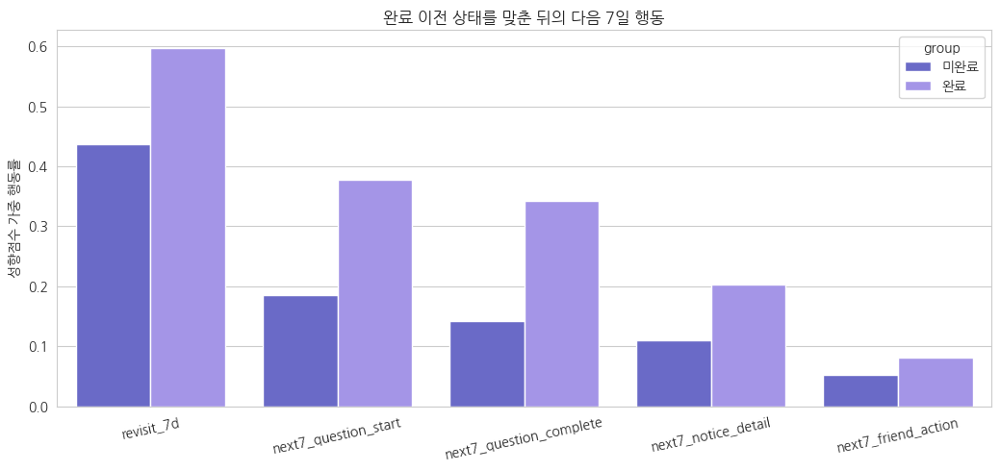

가중치로 맞춘 것은 기록에 있는 완료 전 조건이다. 동기나 오프라인 친구관계 같은 차이는 남아 있다.

In [ ]:
# 가중 후 7일 재방문·질문·관계 행동 차이
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    weighted_results = []
    weighted_rates = []
    outcomes = ['revisit_7d', 'next7_question_start', 'next7_question_complete', 'next7_notice_detail', 'next7_friend_action']
    for outcome in outcomes:
        for t, label in [(0, '미완료'), (1, '완료')]:
            g = ps[ps.completed_after_start.eq(t)]
            weighted_rates.append([outcome, label, len(g), np.average(g[outcome], weights=g.iptw)])
        fit = sm.WLS(ps[outcome].astype(float), sm.add_constant(ps.completed_after_start.astype(float)), weights=ps.iptw).fit(cov_type='HC3')
        weighted_results.append([outcome, fit.params['completed_after_start'], fit.conf_int().loc['completed_after_start', 0], fit.conf_int().loc['completed_after_start', 1], fit.pvalues['completed_after_start']])
    weighted_rates = pd.DataFrame(weighted_rates, columns=['outcome', 'group', 'n', 'weighted_rate'])
    weighted_results = pd.DataFrame(weighted_results, columns=['outcome', 'weighted_risk_difference', 'ci_low', 'ci_high', 'p_value'])
    display(save_table(weighted_rates, '86_iptw_weighted_outcome_rates'))
    display(save_table(weighted_results, '87_iptw_completion_next7d_effects'))
    plt.figure(figsize=(10.5, 5))
    sns.barplot(data=weighted_rates, x='outcome', y='weighted_rate', hue='group', palette=COLORS[:2])
    plt.xlabel('')
    plt.ylabel('성향점수 가중 행동률')
    plt.xticks(rotation=12)
    plt.title('완료 이전 상태를 맞춘 뒤의 다음 7일 행동')
    savefig('64_iptw_completion_next7d')
    display(Markdown('가중치로 맞춘 것은 기록에 있는 완료 전 조건이다. 동기나 오프라인 친구관계 같은 차이는 남아 있다.'))


- 완료 전 조건을 맞춘 후 완료군의 7일 재방문율 차이는 +16.09%p, 다음 질문 완료율 차이는 +19.99%p다.
- 관측된 연관이며 완료를 유도했을 때 같은 폭으로 개선되는지는 별도 실험이 필요하다.


### 3-4-9. 방문 회차·학교·날짜별 차이

- 방문 회차와 학교·날짜를 나눠 전체 평균에 가려진 차이를 살펴봤다. 회차별로 남아 있는 사용자와 날짜별 유입 구성이 달라 개인의 변화나 개편 효과와 일치하지는 않는다.


,visit_band,visits,users,median_events,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,friend_action_rate
0,1회,140663,140663,10.0000,0.1888,0.1159,0.0830,0.2136,0.0526
1,2회,80559,80559,7.0000,0.1925,0.1353,0.0978,0.1676,0.0474
2,3회,52683,52683,7.0000,0.2056,0.1522,0.1098,0.1382,0.0473
3,4~5회,66433,37647,7.0000,0.2274,0.1764,0.1284,0.1139,0.0451
4,6~10회,84739,23003,6.0000,0.2556,0.2046,0.1494,0.0939,0.0403
5,11회 이상,201910,11032,6.0000,0.3259,0.2770,0.2121,0.0922,0.0325


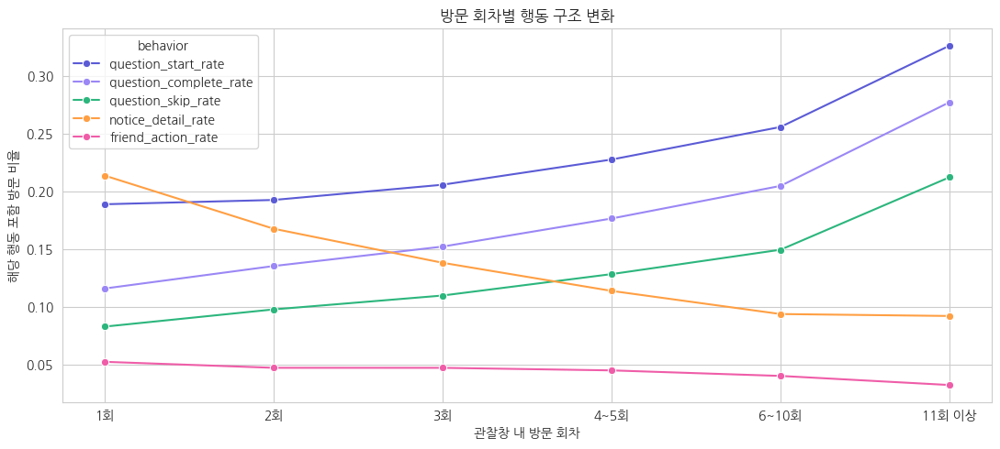

첫 방문은 Hackle 관찰기간에 처음 남은 방문이다. 가입 후 첫 방문과는 다르다.

In [ ]:
# 관측 방문 회차별 행동 구성
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    lifecycle = visit_ordered.copy()
    lifecycle['visit_band'] = pd.cut(lifecycle.observed_visit_no, [0, 1, 2, 3, 5, 10, np.inf], labels=['1회', '2회', '3회', '4~5회', '6~10회', '11회 이상'])
    lifecycle_summary = lifecycle.groupby('visit_band', observed=True).agg(visits=('visit_id', 'nunique'), users=('user_id', 'nunique'), median_events=('event_count', 'median'), question_start_rate=('question_start_flag', 'mean'), question_complete_rate=('question_complete_flag', 'mean'), question_skip_rate=('question_skip_flag', 'mean'), notice_detail_rate=('notice_detail_flag', 'mean'), friend_action_rate=('friend_flag', 'mean')).reset_index()
    display(save_table(lifecycle_summary, '88_behavior_by_visit_number'))
    life_long = lifecycle_summary.melt(id_vars=['visit_band', 'visits', 'users'], value_vars=['question_start_rate', 'question_complete_rate', 'question_skip_rate', 'notice_detail_rate', 'friend_action_rate'], var_name='behavior', value_name='rate')
    plt.figure(figsize=(11, 5))
    sns.lineplot(data=life_long, x='visit_band', y='rate', hue='behavior', marker='o', palette=COLORS[:5])
    plt.xlabel('관찰창 내 방문 회차')
    plt.ylabel('해당 행동 포함 방문 비율')
    plt.title('방문 회차별 행동 구조 변화')
    savefig('65_behavior_by_visit_number')
    display(Markdown('첫 방문은 Hackle 관찰기간에 처음 남은 방문이다. 가입 후 첫 방문과는 다르다.'))


- 첫 방문과 11회 이상 방문을 비교하면 알림 상세 비율은 21.36%→9.22%, 친구 행동은 5.26%→3.25%다.
- 질문 완료 비율은 11.59%→27.70%다. 남아 있는 사용자의 구성이 달라 개인별 변화로 해석하지 않는다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,school_id,visits,start_visits,complete_after_start_visits,notice_after_complete_visits,share_after_start_visits,complete_given_start,notice_given_complete,share_given_start,school_alias
0,4867,4336,2120,1903,580,181,0.8976,0.3048,0.0854,학교 1
1,47,3963,1969,1712,669,193,0.8695,0.3908,0.0980,학교 2
2,400,3830,1704,1450,183,45,0.8509,0.1262,0.0264,학교 3
3,215,3523,1616,1403,536,195,0.8682,0.3820,0.1207,학교 4
4,636,2058,1123,970,177,15,0.8638,0.1825,0.0134,학교 5
5,418,2189,1017,885,49,4,0.8702,0.0554,0.0039,학교 6
6,4030,1755,894,824,35,1,0.9217,0.0425,0.0011,학교 7
7,3829,2189,871,806,159,75,0.9254,0.1973,0.0861,학교 8
8,3592,1901,834,691,146,53,0.8285,0.2113,0.0635,학교 9
9,196,1748,767,675,56,1,0.8801,0.0830,0.0013,학교 10


,metric,schools,weighted_rate,min_rate,median_rate,max_rate,i2
0,시작→완료,24,0.8708,0.7677,0.8751,0.9254,0.9019
1,완료→알림상세,24,0.1939,0.0404,0.1415,0.3908,0.9881
2,시작→공유,24,0.0466,0.0000,0.0286,0.1207,0.9790


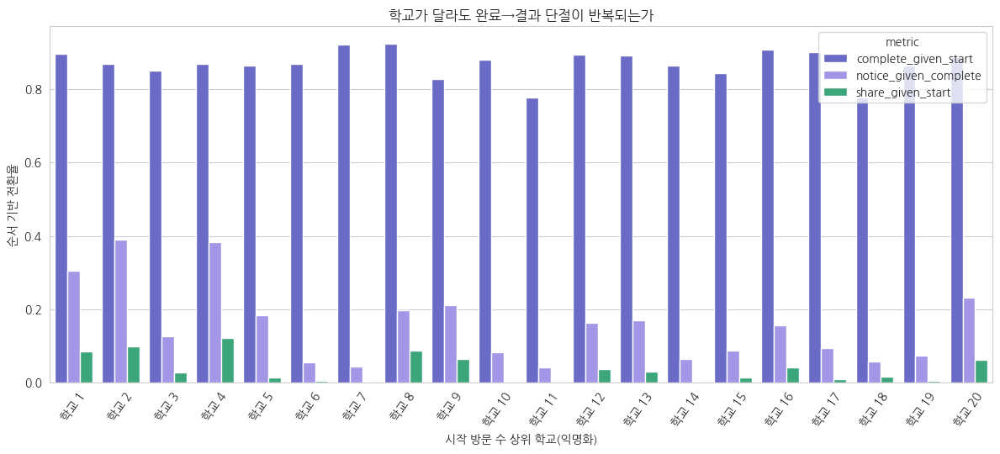

In [ ]:
# 학교별 순서 기반 전환 · 학교 간 편차
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    school_flow = con.execute("\n    SELECT v.school_id,COUNT(*) visits,\n           COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL) start_visits,\n           COUNT(*) FILTER(WHERE o.qcomplete_order IS NOT NULL) complete_after_start_visits,\n           COUNT(*) FILTER(WHERE o.notice_after_complete=1) notice_after_complete_visits,\n           COUNT(*) FILTER(WHERE o.first_share_order>o.qstart_order) share_after_start_visits\n    FROM hackle_visit_interaction v JOIN visit_order_final_v2 o USING(visit_id)\n    WHERE v.school_id IS NOT NULL AND TRIM(v.school_id)<>''\n    GROUP BY 1 HAVING COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL)>=500\n    ORDER BY start_visits DESC\n    ").df()
    school_flow['complete_given_start'] = school_flow.complete_after_start_visits / school_flow.start_visits
    school_flow['notice_given_complete'] = school_flow.notice_after_complete_visits / school_flow.complete_after_start_visits
    school_flow['share_given_start'] = school_flow.share_after_start_visits / school_flow.start_visits
    school_flow['school_alias'] = ['학교 ' + str(i + 1) for i in range(len(school_flow))]
    display(save_table(school_flow, '89_school_flow_robustness'))

    def heterogeneity_row(df, rate_col, n_col, label):
        p = df[rate_col].clip(1e-06, 1 - 1e-06)
        n = df[n_col].clip(lower=1)
        var = p * (1 - p) / n
        w = 1 / var
        pooled = np.average(p, weights=n)
        q = np.sum(w * (p - np.average(p, weights=w)) ** 2)
        dfree = max(len(df) - 1, 1)
        i2 = max(0, (q - dfree) / q) if q > 0 else 0
        return [label, len(df), pooled, p.min(), p.median(), p.max(), i2]
    heterogeneity = pd.DataFrame([heterogeneity_row(school_flow, 'complete_given_start', 'start_visits', '시작→완료'), heterogeneity_row(school_flow, 'notice_given_complete', 'complete_after_start_visits', '완료→알림상세'), heterogeneity_row(school_flow, 'share_given_start', 'start_visits', '시작→공유')], columns=['metric', 'schools', 'weighted_rate', 'min_rate', 'median_rate', 'max_rate', 'i2'])
    display(save_table(heterogeneity, '90_school_flow_heterogeneity'))
    top_school = school_flow.head(20).copy()
    sf = top_school.melt(id_vars=['school_alias', 'start_visits'], value_vars=['complete_given_start', 'notice_given_complete', 'share_given_start'], var_name='metric', value_name='rate')
    plt.figure(figsize=(12, 5.5))
    sns.barplot(data=sf, x='school_alias', y='rate', hue='metric', palette=COLORS[:3])
    plt.xlabel('시작 방문 수 상위 학교(익명화)')
    plt.ylabel('순서 기반 전환율')
    plt.xticks(rotation=55)
    plt.title('학교가 달라도 완료→결과 단절이 반복되는가')
    savefig('66_school_flow_robustness')


- 시작 방문이 충분한 24개 학교의 완료→알림 상세 도달률은 4.04~39.08%, 중앙값은 14.15%다.
- 학교별 집계는 전체 방문 평균과 분모가 다르다.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,visit_date,visits,start_visits,complete_after_start_visits,notice_after_complete_visits,share_after_start_visits,complete_given_start,notice_given_complete,share_given_start
0,2023-07-18,54479,12163,9192,1530,363,0.7557,0.1664,0.0298
1,2023-07-19,43666,10806,8338,1103,289,0.7716,0.1323,0.0267
2,2023-07-20,57418,13543,10054,1520,298,0.7424,0.1512,0.0220
3,2023-07-21,59061,13735,10182,1451,285,0.7413,0.1425,0.0207
4,2023-07-22,40433,9465,7458,832,212,0.7880,0.1116,0.0224
5,2023-07-23,50034,11846,8843,1111,226,0.7465,0.1256,0.0191
6,2023-07-24,37569,8978,6854,731,163,0.7634,0.1067,0.0182
7,2023-07-25,33426,8136,6255,694,162,0.7688,0.1110,0.0199
8,2023-07-26,31204,7466,5691,627,154,0.7623,0.1102,0.0206
9,2023-07-27,44953,9560,6787,913,182,0.7099,0.1345,0.0190


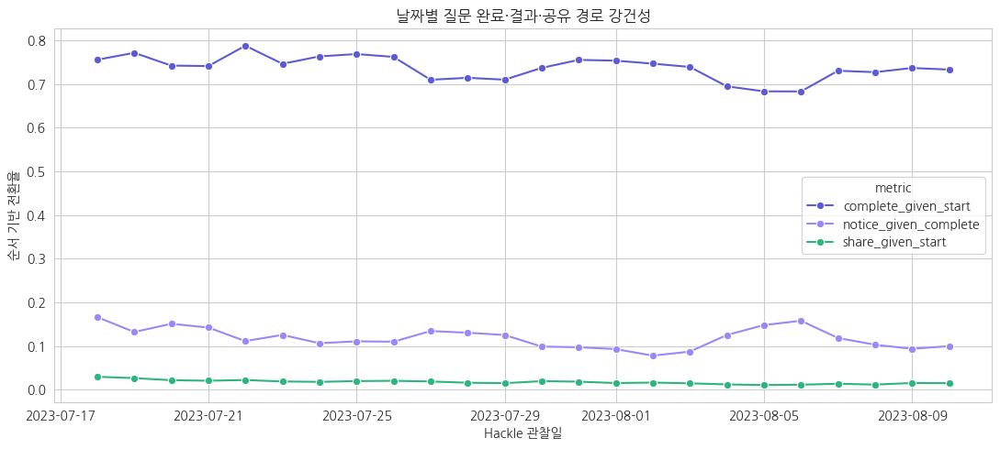

In [ ]:
# 날짜별 질문 완료·공유·알림 상세 전환
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    daily_flow = con.execute('\n    SELECT v.visit_date,COUNT(*) visits,\n           COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL) start_visits,\n           COUNT(*) FILTER(WHERE o.qcomplete_order IS NOT NULL) complete_after_start_visits,\n           COUNT(*) FILTER(WHERE o.notice_after_complete=1) notice_after_complete_visits,\n           COUNT(*) FILTER(WHERE o.first_share_order>o.qstart_order) share_after_start_visits\n    FROM hackle_visit_interaction v JOIN visit_order_final_v2 o USING(visit_id)\n    GROUP BY 1 HAVING COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL)>=500 ORDER BY 1\n    ').df()
    daily_flow['complete_given_start'] = daily_flow.complete_after_start_visits / daily_flow.start_visits
    daily_flow['notice_given_complete'] = daily_flow.notice_after_complete_visits / daily_flow.complete_after_start_visits
    daily_flow['share_given_start'] = daily_flow.share_after_start_visits / daily_flow.start_visits
    display(save_table(daily_flow, '91_daily_flow_robustness'))
    dl = daily_flow.melt(id_vars=['visit_date', 'start_visits'], value_vars=['complete_given_start', 'notice_given_complete', 'share_given_start'], var_name='metric', value_name='rate')
    plt.figure(figsize=(11, 5))
    sns.lineplot(data=dl, x='visit_date', y='rate', hue='metric', marker='o', palette=COLORS[:3])
    plt.xlabel('Hackle 관찰일')
    plt.ylabel('순서 기반 전환율')
    plt.title('날짜별 질문 완료·결과·공유 경로 강건성')
    savefig('67_daily_flow_robustness')


- 완료→알림 상세 도달률은 7월 18일 16.64%에서 8월 2일 7.82%까지 내려갔고, 8월 6일에는 15.81%로 다시 높아졌다. 일별 변동이 컸다.
- 시작→완료는 대부분 70%대였지만 8월 4~6일에는 60%대로 낮아졌다. 전체 평균만 보면 놓치는 구간이다.


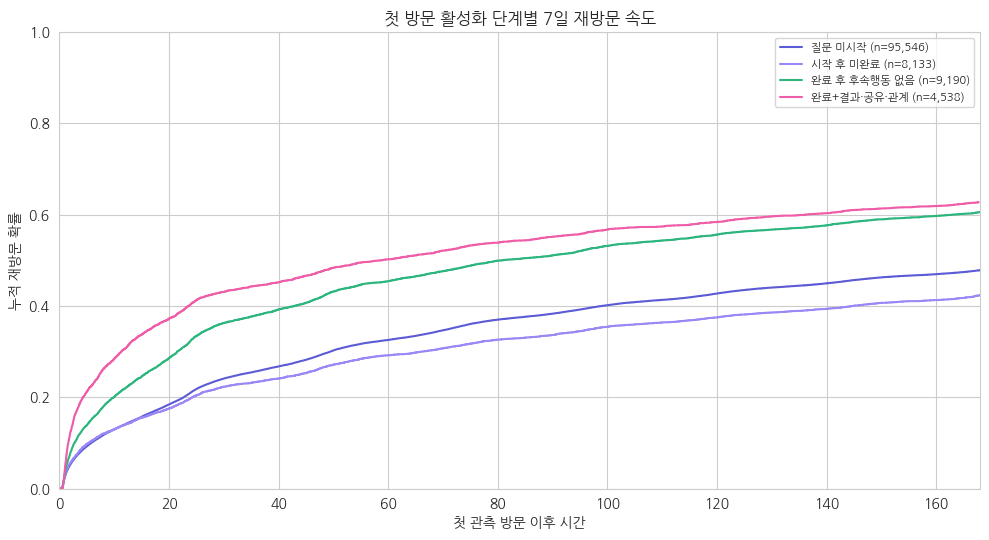

,activation_stage,users,revisit_7d,median_hours_among_returners
0,질문 미시작,95546,0.4782,29.4614
1,시작 후 미완료,8133,0.4235,26.3982
2,완료 후 후속행동 없음,9190,0.6055,21.7917
3,완료+결과·공유·관계,4538,0.6276,12.5497


In [ ]:
# 첫 방문 참여 단계별 재방문 시간
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    survival_final = final_first.copy()
    survival_final['hours_to_next'] = (survival_final.next_visit_start - survival_final.visit_start).dt.total_seconds() / 3600
    survival_final['event_7d'] = (survival_final.hours_to_next <= 168).astype(int)
    survival_final['follow_hours'] = np.where(survival_final.event_7d.eq(1), survival_final.hours_to_next, 168)
    plt.figure(figsize=(10, 5.5))
    survival_rates = []
    for stage, color in zip(stage_order, COLORS[:5]):
        g = survival_final[survival_final.activation_stage.eq(stage)]
        if len(g) < 100:
            continue
        km = km_curve(g.follow_hours, g.event_7d, max_hours=168)
        plt.step(km.hours, 1 - km.survival, where='post', label=f'{stage} (n={len(g):,})', color=color)
        survival_rates.append([stage, len(g), g.event_7d.mean(), g.loc[g.event_7d.eq(1), 'hours_to_next'].median()])
    plt.xlim(0, 168)
    plt.ylim(0, 1)
    plt.xlabel('첫 관측 방문 이후 시간')
    plt.ylabel('누적 재방문 확률')
    plt.title('첫 방문 활성화 단계별 7일 재방문 속도')
    plt.legend(fontsize=8)
    savefig('68_activation_stage_revisit_survival')
    survival_rates = pd.DataFrame(survival_rates, columns=['activation_stage', 'users', 'revisit_7d', 'median_hours_among_returners'])
    display(save_table(survival_rates, '92_activation_stage_survival_summary'))


- 완료 후 결과·공유·관계 행동 그룹의 복귀시간 중앙값은 약 12.55시간, 지정된 후속 행동이 없는 그룹은 약 21.79시간이었다.
- 이는 7일 내 재방문한 사람만의 간격이므로 전체 재방문율과 함께 해석한다.


### 3-4-10. 완료 이후 연결을 위한 실험 정리

- 완료 뒤 알림 상세로 이어지는 비율을 높였을 때의 규모를 계산했다. 아래 수치는 현재 완료율이 유지된다는 가정에 따른 시나리오이며, 실제 개선 성과는 아니다.


,scenario,assumed_notice_given_complete,result_reaches_per_10k_starts,additional_vs_current
0,현재 관측,0.1245,918.5340,0.0000
1,완료→결과 15%,0.1500,"1,106.3235",187.7895
2,완료→결과 20%,0.2000,"1,475.0980",556.5640
3,완료→결과 30%,0.3000,"2,212.6470","1,294.1130"


/tmp/ipykernel_804/365184117.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=scenarios, x='scenario', y='result_reaches_per_10k_starts', palette=COLORS[:4])


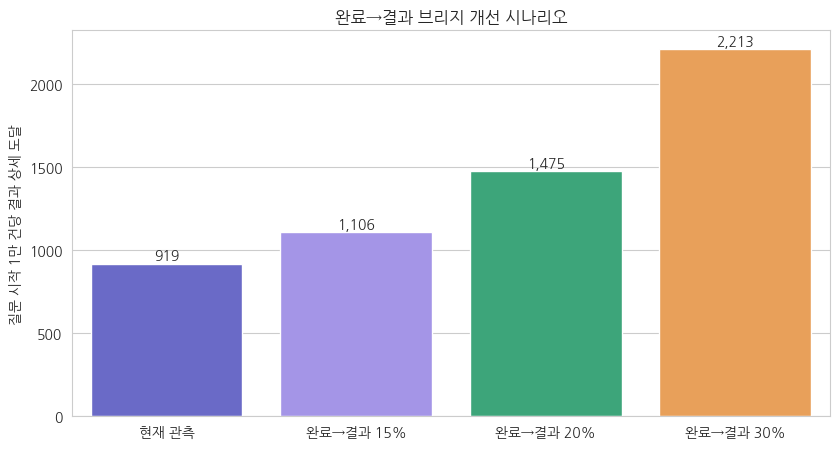

현재 완료율을 고정한 시나리오다. 완료 화면의 결과 카드와 반응 버튼은 별도 실험이 필요하다.

In [ ]:
# 완료 후 결과 도달률 개선 시나리오
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    start_n = int(social_loop.loc[social_loop.transition.eq('질문 시작→완료'), 'denominator'].iloc[0])
    complete_rate = float(social_loop.loc[social_loop.transition.eq('질문 시작→완료'), 'rate'].iloc[0])
    notice_rate = float(social_loop.loc[social_loop.transition.eq('완료→알림상세'), 'rate'].iloc[0])
    scenarios = pd.DataFrame({'scenario': ['현재 관측', '완료→결과 15%', '완료→결과 20%', '완료→결과 30%'], 'assumed_notice_given_complete': [notice_rate, 0.15, 0.2, 0.3]})
    scenarios['result_reaches_per_10k_starts'] = 10000 * complete_rate * scenarios.assumed_notice_given_complete
    scenarios['additional_vs_current'] = scenarios.result_reaches_per_10k_starts - scenarios.result_reaches_per_10k_starts.iloc[0]
    display(save_table(scenarios, '93_result_bridge_scenario'))
    plt.figure(figsize=(8.5, 4.6))
    ax = sns.barplot(data=scenarios, x='scenario', y='result_reaches_per_10k_starts', palette=COLORS[:4])
    plt.xlabel('')
    plt.ylabel('질문 시작 1만 건당 결과 상세 도달')
    plt.title('완료→결과 브리지 개선 시나리오')
    for p, v in zip(ax.patches, scenarios.result_reaches_per_10k_starts):
        ax.text(p.get_x() + p.get_width() / 2, v + 25, f'{v:,.0f}', ha='center')
    savefig('69_result_bridge_scenario')
    display(Markdown('현재 완료율을 고정한 시나리오다. 완료 화면의 결과 카드와 반응 버튼은 별도 실험이 필요하다.'))


- 완료→알림 상세 도달률을 20%로 높인다고 가정하면, 질문 시작 1만 건당 상세 도달이 현재보다 약 557건 늘어난다. 완료 이후 동선 개선의 규모를 가늠하기 위한 계산이다.


In [ ]:
# Interaction 근거 정리 · 개선 실험 우선순위
if INTERACTION_EVENT_DETAIL_AVAILABLE:
    iptw_revisit = weighted_results.loc[weighted_results.outcome.eq('revisit_7d')].iloc[0]
    iptw_next_complete = weighted_results.loc[weighted_results.outcome.eq('next7_question_complete')].iloc[0]
    start_share_row = social_loop.loc[social_loop.transition.eq('질문 시작→공유')].iloc[0]
    share_row = social_loop.loc[social_loop.transition.eq('완료→공유')].iloc[0]
    notice_row = social_loop.loc[social_loop.transition.eq('완료→알림상세')].iloc[0]
    final_evidence = pd.DataFrame([['완료 이후 결과 브리지', f'순서 기반 완료→알림상세 {notice_row.rate:.1%}', '완료 화면에서 결과를 바로 보여주고 알림센터 우회를 줄이는 실험', '최우선'], ['공유 루프', f'시작→공유 {start_share_row.rate:.1%}, 완료→공유 {share_row.rate:.1%}', '결과 카드 공유와 공유 후 친구 반응을 하나의 추적 가능한 루프로 연결', '최우선'], ['다음 방문 연관', f'완료 이전 상태 가중 후 7일 재방문 위험차 {iptw_revisit.weighted_risk_difference * 100:+.1f}%p', '질문 완료 여부가 아니라 완료 뒤 결과·반응 경험을 무작위 실험', '최우선'], ['다음 방문의 질', f'가중 후 다음 7일 질문완료 위험차 {iptw_next_complete.weighted_risk_difference * 100:+.1f}%p', '재방문 KPI와 다음 질문완료 KPI를 함께 사용', '높음'], ['반복 방문 설계', '방문 회차별 질문·결과·관계 행동 구조가 다름', '첫 관측 방문과 반복 방문의 홈·CTA·콘텐츠를 분리', '높음'], ['학교 강건성', f'{len(school_flow):,}개 충분표본 학교에서 전환 경로 재검증', '학교별 별도 제품보다 공통 병목을 먼저 고치고 편차 큰 학교만 후속 진단', '높음'], ['계측 공백', '공식 open_ping 0건', 'question_set_id·question_piece_id·result_id·notification_id를 공통 키로 저장', '필수']], columns=['evidence', 'result', 'product_test_or_decision', 'priority'])
    display(save_table(final_evidence, '94_final_evidence_and_experiments'))
    final_qa = pd.DataFrame([['기존 셀 보존', True, 'G 절만 하단에 추가'], ['질문 공유 이벤트 복원', True, 'click_question_share 99_기타에서 별도 추출'], ['순서 기반 완료·후속 행동', True, 'event_order로 시작<완료<후속행동 확인'], ['다음 7일 행동의 질', True, '재방문·질문시작·질문완료·알림상세·친구행동'], ['성향점수 공통지지영역', bool(len(ps) > 0 and propensity_diagnostics.retained_share.iloc[0] > 0.5), '완료 이전 변수만 사용'], ['가중 후 균형 확인', bool(balance.smd_after.abs().max() < 0.25), '절대 SMD 점검'], ['학교 강건성', bool(len(school_flow) >= 3), '학교별 시작 방문 500건 이상'], ['날짜 강건성', bool(len(daily_flow) >= 7), '일별 시작 방문 500건 이상'], ['우측 검열', True, '7일 관찰 가능한 첫 방문만 사용'], ['Ping 과대해석 방지', True, '알림 상세는 대리경로로만 사용'], ['인과 경계', True, '관찰 연관과 A/B 테스트 분리'], ['표·차트 화면 출력', True, 'CSV·PNG 파일 생성 없이 결과 변수와 셀 출력 사용']], columns=['check', 'pass', 'evidence'])
    display(save_table(final_qa, '95_final_extension_qa'))
    assert final_qa['pass'].all(), final_qa.loc[~final_qa['pass']]
    print(f"FINAL EXTENSION QA: PASS {final_qa['pass'].sum()} / FAIL 0")
team7_release_unused('368', '3-4 완료')
team7_close_connections('interaction')


,evidence,result,product_test_or_decision,priority
0,완료 이후 결과 브리지,순서 기반 완료→알림상세 12.5%,완료 화면에서 결과를 바로 보여주고 알림센터 우회를 줄이는 실험,최우선
1,공유 루프,"시작→공유 1.9%, 완료→공유 3.0%",결과 카드 공유와 공유 후 친구 반응을 하나의 추적 가능한 루프로 연결,최우선
2,다음 방문 연관,완료 이전 상태 가중 후 7일 재방문 위험차 +16.1%p,질문 완료 여부가 아니라 완료 뒤 결과·반응 경험을 무작위 실험,최우선
3,다음 방문의 질,가중 후 다음 7일 질문완료 위험차 +20.0%p,재방문 KPI와 다음 질문완료 KPI를 함께 사용,높음
4,반복 방문 설계,방문 회차별 질문·결과·관계 행동 구조가 다름,첫 관측 방문과 반복 방문의 홈·CTA·콘텐츠를 분리,높음
5,학교 강건성,24개 충분표본 학교에서 전환 경로 재검증,학교별 별도 제품보다 공통 병목을 먼저 고치고 편차 큰 학교만 후속 진단,높음
6,계측 공백,공식 open_ping 0건,question_set_id·question_piece_id·result_id·no...,필수


,check,pass,evidence
0,기존 셀 보존,True,G 절만 하단에 추가
1,질문 공유 이벤트 복원,True,click_question_share 99_기타에서 별도 추출
2,순서 기반 완료·후속 행동,True,event_order로 시작<완료<후속행동 확인
3,다음 7일 행동의 질,True,재방문·질문시작·질문완료·알림상세·친구행동
4,성향점수 공통지지영역,True,완료 이전 변수만 사용
5,가중 후 균형 확인,True,절대 SMD 점검
6,학교 강건성,True,학교별 시작 방문 500건 이상
7,날짜 강건성,True,일별 시작 방문 500건 이상
8,우측 검열,True,7일 관찰 가능한 첫 방문만 사용
9,Ping 과대해석 방지,True,알림 상세는 대리경로로만 사용


FINAL EXTENSION QA: PASS 12 / FAIL 0
[3-4 완료] 사용이 끝난 변수 67개 정리
[3-4 완료] Python 사용 RAM 3.26 GB / 시스템 여유 RAM 8.95 GB


**Interaction 정리**

- 질문을 마친 뒤 결과 확인·공유·친구 반응으로 이어지는 동선이 우선 실험 대상이다. 단순 결과 화면 도달보다 실제 반응까지 연결되는지가 중요하다.
- 실험에서는 재방문 여부와 함께 다음 질문 완료·관계 행동을 측정해야 한다. Ping 열람과 반응을 직접 연결할 로그도 보완할 필요가 있다.


## 3-5. Value

- 10개 학교의 사용자 행동을 군집화하고, Ping 수신·답장·힌트 열람과 이후 투표 참여를 비교했다.
- 최종 답장 상태와 다음 날 투표의 연관성, 학교별 답장률과 활성 일수의 관계를 구분해 분석했다.


### 3-5-1. 사용자와 이용량

- 친구 수, 하트 잔액, 질문세트 참여, 출석 분포를 확인했다. 자료별 분석 대상과 분모는 다르다.


In [ ]:
# Value 입력 마트·분석 범위
value_root = Path(globals().get('PREPROCESSED_ROOT', '/content/team7_processed'))
value_specs = {
    'mart_user_acquisition_profile_v2': ('viral_school', ['user_id', 'current_school_id', 'gender', 'current_grade', 'contacts_count_source', 'current_friend_list_length', 'current_point_snapshot']),
    'mart_user_viral_profile_v2': ('viral_school', ['user_id', 'sent_request_count', 'received_request_count']),
    'mart_question_set_record_v2': ('question_candidate', ['question_set_id', 'question_set_owner_user_id', 'question_set_status']),
    'mart_vote_record_v2': ('question_candidate', ['user_question_record_id', 'voter_user_id', 'chosen_user_id', 'vote_record_created_at', 'ping_has_read_current', 'ping_answer_status_current', 'ping_opened_times_current']),
    'mart_point_payment_event': ('hackle_mixed', ['user_id', 'event_type', 'point_amount_abs']),
    'mart_value_event_v2': ('hackle_mixed', ['service_user_id', 'event_type', 'point_amount_abs']),
    'mart_attendance_record_v2': ('lifecycle_safety_attendance', ['user_id', 'attendance_list_length']),
}
value_paths = {name: value_root / group / f'{name}_clean.csv.gz'
               for name, (group, columns) in value_specs.items()}
value_missing = [str(path) for path in value_paths.values() if not path.is_file()]
if value_missing:
    raise FileNotFoundError('2번의 정제 결과가 필요합니다.\n' + '\n'.join(value_missing))

def value_read_clean(name, usecols=None):
    columns = list(usecols or value_specs[name][1])
    frame = pd.read_csv(value_paths[name], usecols=columns, low_memory=False, na_values=['\\N'])
    text_columns = {'gender', 'question_set_status', 'vote_record_created_at', 'ping_answer_status_current', 'event_type'}
    for column in columns:
        if column not in text_columns:
            frame[column] = pd.to_numeric(frame[column], errors='coerce')
    return frame

def value_drop(*names):
    for name in names:
        globals().pop(name, None)
    plt.close('all')
    gc.collect()

value_sm = sys.modules['statsmodels.api']
koreanize_matplotlib.koreanize()
display(pd.DataFrame([{'정제 마트': name, '입력 경로': str(path)} for name, path in value_paths.items()]))
print('Value 입력 확인 완료.')


,정제 마트,입력 경로
0,mart_user_acquisition_profile_v2,/content/team7_processed/viral_school/mart_use...
1,mart_user_viral_profile_v2,/content/team7_processed/viral_school/mart_use...
2,mart_question_set_record_v2,/content/team7_processed/question_candidate/ma...
3,mart_vote_record_v2,/content/team7_processed/question_candidate/ma...
4,mart_point_payment_event,/content/team7_processed/hackle_mixed/mart_poi...
5,mart_value_event_v2,/content/team7_processed/hackle_mixed/mart_val...
6,mart_attendance_record_v2,/content/team7_processed/lifecycle_safety_atte...


Value: 2번 전처리 결과 연결 완료. 표·차트·중간 분석 결과는 Drive에 저장하지 않습니다.


- 사용자·친구 요청·질문세트·투표·결제·하트 사용·출석 마트를 사용했다. 전체 프로필과 질문 참여자를 같은 모집단으로 해석하지 않는다.



1. accounts_user : 친구 수 및 보유 포인트 구간 분포 분석
- 총 유저 수: 677,085명

[친구 수 구간 분포]
  친구 수 구간  유저 수(명)  점유율(%)
   0명(고립)     2874  0.4000
     1~5명    13284  2.0000
    6~15명    38821  5.7000
   16~30명   108242 16.0000
   31~50명   194029 28.7000
  51~100명   268446 39.6000
101명+(헤비)    51389  7.6000

[보유 잔여 포인트 구간 분포]
     포인트 구간  유저 수(명)  점유율(%)
         0P      198  0.0000
     1~500P   206093 30.4000
  501~1500P   224053 33.1000
 1501~3000P   137672 20.3000
 3001~5000P    69287 10.2000
5001~10000P    33435  4.9000
10001P+(고래)     6347  0.9000


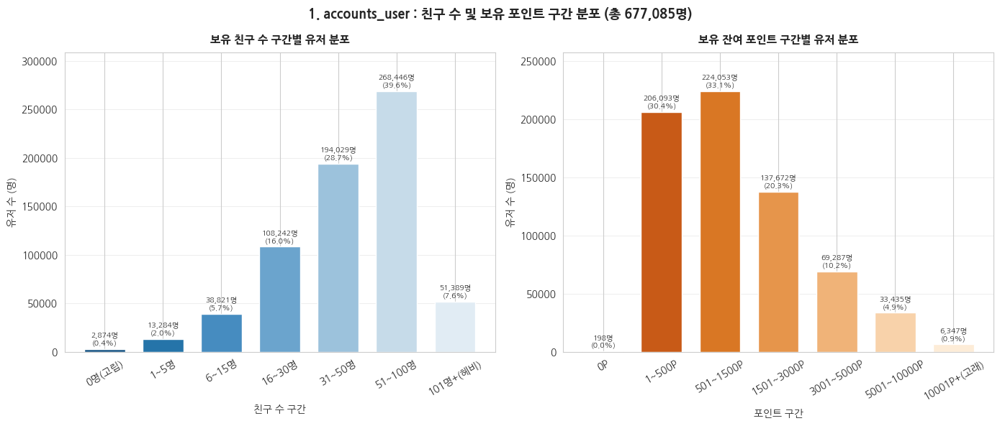

In [ ]:
# 친구 수·보유 하트 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('1. accounts_user : 친구 수 및 보유 포인트 구간 분포 분석')
print('=' * 70)
value_df_u = value_read_clean('mart_user_acquisition_profile_v2', usecols=['user_id', 'current_friend_list_length', 'current_point_snapshot'])
value_total_u = len(value_df_u)
value_f_bins = [-1, 0, 5, 15, 30, 50, 100, np.inf]
value_f_labels = ['0명(고립)', '1~5명', '6~15명', '16~30명', '31~50명', '51~100명', '101명+(헤비)']
value_df_u['friend_tier'] = pd.cut(value_df_u['current_friend_list_length'].fillna(0), bins=value_f_bins, labels=value_f_labels)
value_p_bins = [-1, 0, 500, 1500, 3000, 5000, 10000, np.inf]
value_p_labels = ['0P', '1~500P', '501~1500P', '1501~3000P', '3001~5000P', '5001~10000P', '10001P+(고래)']
value_df_u['point_tier'] = pd.cut(value_df_u['current_point_snapshot'].fillna(0), bins=value_p_bins, labels=value_p_labels)
value_f_summary = value_df_u['friend_tier'].value_counts().reindex(value_f_labels, fill_value=0).reset_index()
value_f_summary.columns = ['친구 수 구간', '유저 수(명)']
value_f_summary['점유율(%)'] = (value_f_summary['유저 수(명)'] / value_total_u * 100).round(1)
value_p_summary = value_df_u['point_tier'].value_counts().reindex(value_p_labels, fill_value=0).reset_index()
value_p_summary.columns = ['포인트 구간', '유저 수(명)']
value_p_summary['점유율(%)'] = (value_p_summary['유저 수(명)'] / value_total_u * 100).round(1)
print(f'- 총 유저 수: {value_total_u:,}명')
print('\n[친구 수 구간 분포]')
print(value_f_summary.to_string(index=False))
print('\n[보유 잔여 포인트 구간 분포]')
print(value_p_summary.to_string(index=False))
value_fig, value_axes = plt.subplots(1, 2, figsize=(14, 6))
value_fig.suptitle(f'1. accounts_user : 친구 수 및 보유 포인트 구간 분포 (총 {value_total_u:,}명)', fontsize=13, weight='bold', y=0.98)
value_blue_palette = ['#1d5987', '#2574a9', '#468cc0', '#6ba4cd', '#9cc2dc', '#c6dbe9', '#e1ecf4']
value_bars1 = value_axes[0].bar(value_f_labels, value_f_summary['유저 수(명)'], color=value_blue_palette, width=0.7)
value_axes[0].set_title('보유 친구 수 구간별 유저 분포', fontsize=11, weight='bold', pad=10)
value_axes[0].set_xlabel('친구 수 구간', fontsize=10, labelpad=8)
value_axes[0].set_ylabel('유저 수 (명)', fontsize=10)
value_axes[0].set_ylim(0, max(value_f_summary['유저 수(명)']) * 1.15)
value_axes[0].tick_params(axis='x', rotation=30)
value_axes[0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_axes[0].annotate(f'{int(value_h):,}명\n({value_h / value_total_u * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_orange_palette = ['#b84d05', '#c85a17', '#d97724', '#e6954b', '#f0b378', '#f8d2aa', '#fdecd7']
value_bars2 = value_axes[1].bar(value_p_labels, value_p_summary['유저 수(명)'], color=value_orange_palette, width=0.7)
value_axes[1].set_title('보유 잔여 포인트 구간별 유저 분포', fontsize=11, weight='bold', pad=10)
value_axes[1].set_xlabel('포인트 구간', fontsize=10, labelpad=8)
value_axes[1].set_ylabel('유저 수 (명)', fontsize=10)
value_axes[1].set_ylim(0, max(value_p_summary['유저 수(명)']) * 1.15)
value_axes[1].tick_params(axis='x', rotation=30)
value_axes[1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_axes[1].annotate(f'{int(value_h):,}명\n({value_h / value_total_u * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_drop('value_df_u')


**결과**

- 친구가 31~100명인 사용자는 약 68%, 하트 잔액이 1~1,500인 사용자는 약 64%다.
- 하트 잔액은 현재 보유량이며, 결제 경험과 구분한다.



2. polls_questionset : 투표 세트 코어 활동 구간 분포 분석
- 총 코어 유저 수: 4,972명

[시작 수 구간 (started_tier)]
              인원(명)
started_tier       
1회(찍먹)          126
2~5회            374
6~15회          1002
16~40회         2123
41~80회         1066
81회+(헤비)        281

[완주 수 구간 (completed_tier)]
                인원(명)
completed_tier       
1회(찍먹)            125
2~5회              326
6~15회            1048
16~40회           2053
41~80회           1023
81회+(헤비)          271

[완주율 구간 (rate_tier)]
            인원(명)
rate_tier        
0%(완주실패)      126
1~50%         125
51~80%        249
81~99%       4472
100%(전부완주)      0


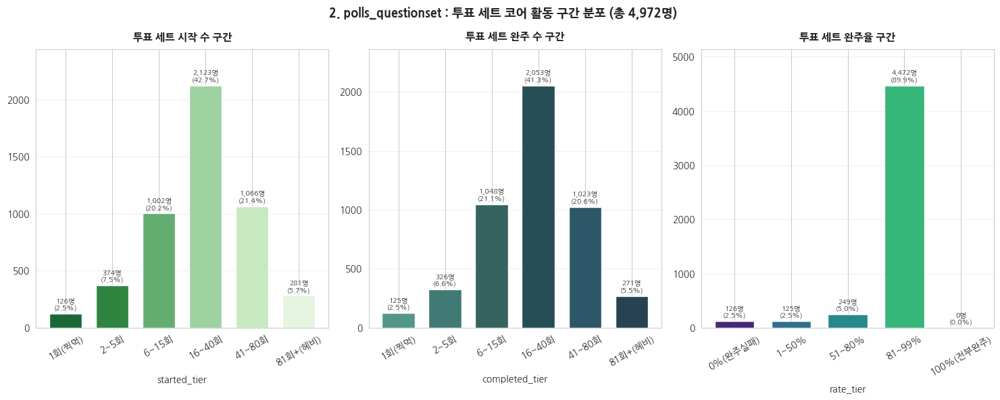

In [ ]:
# 질문세트 시작·완료 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('2. polls_questionset : 투표 세트 코어 활동 구간 분포 분석')
print('=' * 70)
value_df_qs_all = value_read_clean('mart_question_set_record_v2', usecols=['question_set_id', 'question_set_owner_user_id', 'question_set_status'])
value_qs_grouped = value_df_qs_all.groupby('question_set_owner_user_id').agg(started=('question_set_id', 'count'), completed=('question_set_status', lambda value_s: (value_s == 'F').sum())).reset_index()
value_total_qs_users = len(value_qs_grouped)
value_qs_grouped['rate'] = value_qs_grouped['completed'] / value_qs_grouped['started'] * 100
value_s_bins = [0, 1, 5, 15, 40, 80, np.inf]
value_s_labels = ['1회(찍먹)', '2~5회', '6~15회', '16~40회', '41~80회', '81회+(헤비)']
value_qs_grouped['started_tier'] = pd.cut(value_qs_grouped['started'], bins=value_s_bins, labels=value_s_labels)
value_c_bins = [0, 1, 5, 15, 40, 80, np.inf]
value_c_labels = ['1회(찍먹)', '2~5회', '6~15회', '16~40회', '41~80회', '81회+(헤비)']
value_qs_grouped['completed_tier'] = pd.cut(value_qs_grouped['completed'], bins=value_c_bins, labels=value_c_labels)

def value_get_rate_tier(value_r):
    if value_r == 0:
        return '0%(완주실패)'
    elif value_r <= 50:
        return '1~50%'
    elif value_r <= 80:
        return '51~80%'
    elif value_r < 100:
        return '81~99%'
    else:
        return '100%(전부완주)'
value_r_labels = ['0%(완주실패)', '1~50%', '51~80%', '81~99%', '100%(전부완주)']
value_qs_grouped['rate_tier'] = value_qs_grouped['rate'].map(value_get_rate_tier)
print(f'- 총 코어 유저 수: {value_total_qs_users:,}명')
print('\n[시작 수 구간 (started_tier)]')
print(value_qs_grouped['started_tier'].value_counts().reindex(value_s_labels, fill_value=0).to_frame('인원(명)'))
print('\n[완주 수 구간 (completed_tier)]')
print(value_qs_grouped['completed_tier'].value_counts().reindex(value_c_labels, fill_value=0).to_frame('인원(명)'))
print('\n[완주율 구간 (rate_tier)]')
print(value_qs_grouped['rate_tier'].value_counts().reindex(value_r_labels, fill_value=0).to_frame('인원(명)'))
value_fig, value_axes = plt.subplots(1, 3, figsize=(15, 6))
value_fig.suptitle(f'2. polls_questionset : 투표 세트 코어 활동 구간 분포 (총 {value_total_qs_users:,}명)', fontsize=13, weight='bold', y=0.98)
value_palette_green = ['#1b6837', '#2e8540', '#63ad70', '#9ed2a1', '#c7e9c0', '#e5f5e0']
value_palette_teal = ['#529688', '#407a75', '#356360', '#254e56', '#2b5768', '#264253']
value_palette_rate = ['#482677', '#2e6f8e', '#238a8d', '#35b779', '#90d743']
value_s_counts = value_qs_grouped['started_tier'].value_counts().reindex(value_s_labels, fill_value=0)
value_bars1 = value_axes[0].bar(value_s_labels, value_s_counts, color=value_palette_green, width=0.7)
value_axes[0].set_title('투표 세트 시작 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[0].set_xlabel('started_tier', fontsize=10, labelpad=8)
value_axes[0].set_ylim(0, max(value_s_counts) * 1.15)
value_axes[0].tick_params(axis='x', rotation=30)
value_axes[0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_axes[0].annotate(f'{int(value_h):,}명\n({value_h / value_total_qs_users * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_c_counts = value_qs_grouped['completed_tier'].value_counts().reindex(value_c_labels, fill_value=0)
value_bars2 = value_axes[1].bar(value_c_labels, value_c_counts, color=value_palette_teal, width=0.7)
value_axes[1].set_title('투표 세트 완주 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[1].set_xlabel('completed_tier', fontsize=10, labelpad=8)
value_axes[1].set_ylim(0, max(value_c_counts) * 1.15)
value_axes[1].tick_params(axis='x', rotation=30)
value_axes[1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_axes[1].annotate(f'{int(value_h):,}명\n({value_h / value_total_qs_users * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_r_counts = value_qs_grouped['rate_tier'].value_counts().reindex(value_r_labels, fill_value=0)
value_bars3 = value_axes[2].bar(value_r_labels, value_r_counts, color=value_palette_rate, width=0.7)
value_axes[2].set_title('투표 세트 완주율 구간', fontsize=11, weight='bold', pad=10)
value_axes[2].set_xlabel('rate_tier', fontsize=10, labelpad=8)
value_axes[2].set_ylim(0, max(value_r_counts) * 1.15)
value_axes[2].tick_params(axis='x', rotation=30)
value_axes[2].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars3:
    value_h = value_b.get_height()
    value_axes[2].annotate(f'{int(value_h):,}명\n({value_h / value_total_qs_users * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_drop('value_df_qs_all', 'value_qs_grouped')


- 질문세트 기록이 있는 4,972명 중 16~40회 시작한 사람이 2,123명으로 가장 많다. 완료율은 80% 초과~100% 미만 구간에 4,472명이 모여 있다.

- 완료율은 F 상태 세트 수를 시작 세트 수로 나눈 값이다. 질문조각별 투표 기록률과 분모가 다르다.
- 완료 0회인 126명은 가운데 횟수 그래프에서 빠지고, 오른쪽 완료율 그래프에는 0%로 들어간다.



3. accounts_attendance : 누적 출석일수 구간 분포 분석
- 총 유저 수: 349,637명

[출석일수 구간 분포]
   출석일수 구간  유저 수(명)  점유율(%)
        0일    20945  6.0000
 1일(출석 1일)    78867 22.6000
      2~3일    78454 22.4000
  4~7일(1주)    75459 21.6000
     8~15일    63335 18.1000
16~30일(1달)    25265  7.2000
 31일+(초장기)     7312  2.1000


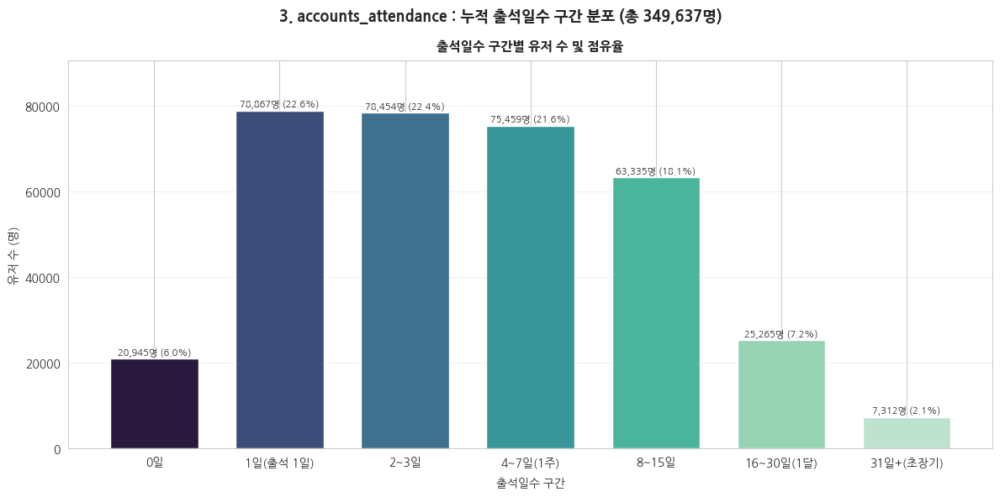

In [ ]:
# 출석 기록 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('3. accounts_attendance : 누적 출석일수 구간 분포 분석')
print('=' * 70)
value_df_att = value_read_clean('mart_attendance_record_v2', usecols=['user_id', 'attendance_list_length'])
value_total_att_users = len(value_df_att)
value_att_bins = [-1, 0, 1, 3, 7, 15, 30, np.inf]
value_att_labels = ['0일', '1일(출석 1일)', '2~3일', '4~7일(1주)', '8~15일', '16~30일(1달)', '31일+(초장기)']
value_df_att['att_tier'] = pd.cut(value_df_att['attendance_list_length'].fillna(0), bins=value_att_bins, labels=value_att_labels)
value_att_summary = value_df_att['att_tier'].value_counts().reindex(value_att_labels, fill_value=0).reset_index()
value_att_summary.columns = ['출석일수 구간', '유저 수(명)']
value_att_summary['점유율(%)'] = (value_att_summary['유저 수(명)'] / value_total_att_users * 100).round(1)
print(f'- 총 유저 수: {value_total_att_users:,}명')
print('\n[출석일수 구간 분포]')
print(value_att_summary.to_string(index=False))
value_fig, value_ax = plt.subplots(figsize=(12, 6))
value_fig.suptitle(f'3. accounts_attendance : 누적 출석일수 구간 분포 (총 {value_total_att_users:,}명)', fontsize=13, weight='bold', y=0.98)
value_att_palette = ['#28193d', '#3d4d7a', '#3f708d', '#389598', '#4bb59b', '#96d3b4', '#bde2cd']
value_bars_att = value_ax.bar(value_att_labels, value_att_summary['유저 수(명)'], color=value_att_palette, width=0.7)
value_ax.set_title('출석일수 구간별 유저 수 및 점유율', fontsize=11, weight='bold', pad=10)
value_ax.set_xlabel('출석일수 구간', fontsize=10, labelpad=8)
value_ax.set_ylabel('유저 수 (명)', fontsize=10)
value_ax.set_ylim(0, max(value_att_summary['유저 수(명)']) * 1.15)
value_ax.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars_att:
    value_h = value_b.get_height()
    value_ax.annotate(f'{int(value_h):,}명 ({value_h / value_total_att_users * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=8, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_drop('value_df_att')


- 출석 1일 구간이 78,867명, 22.6%로 가장 크다. 2~3일과 4~7일 구간도 각각 22.4%, 21.6%로 비슷하다.

- 출석을 누른 날짜를 센 자료라 출석 1회를 곧 하루 이용으로 볼 수는 없다.


### 3-5-2. 관계 행동과 하트 사용

- 친구 요청의 발송·수신 분포와 가입자 수 상위 10개 학교 5,090명의 Ping·하트 사용을 확인했다.



4. accounts_friendrequest : 친구 요청 발송/수신 및 인기도 비율 분포 분석
- 총 친구 요청 활동 유저 수: 673,705명

[친구 요청 발송 수 구간 (sent_tier)]
            인원(명)
sent_tier        
0회          24633
1~2회        25124
3~5회        40764
6~15회      170449
16~30회     211521
31회+       201214

[친구 요청 수신 수 구간 (recv_tier)]
            인원(명)
recv_tier        
0회          12864
1~2회        32790
3~5회        51042
6~15회      157267
16~30회     190002
31회+       229740

[인기도 비율 구간 (ratio_tier)]
               인원(명)
ratio_tier          
0~0.2(탐색형)     96725
0.2~0.4       151892
0.4~0.6(균형형)  191204
0.6~0.8       159372
0.8~1.0(인기형)   74512


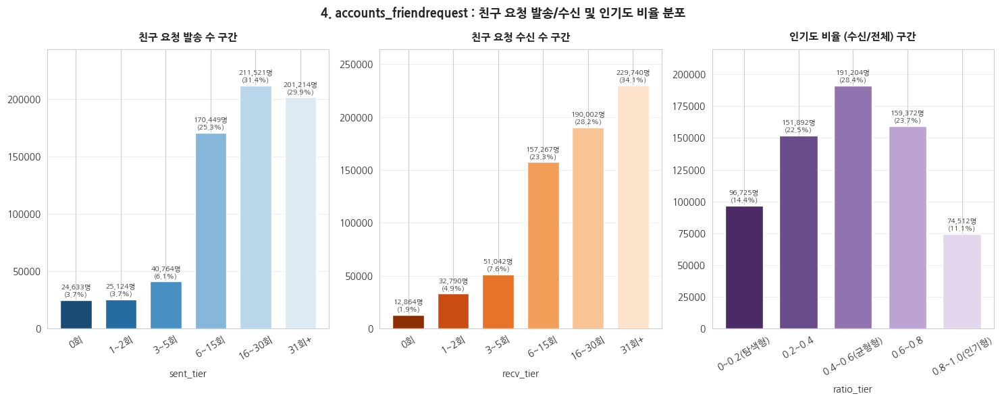

In [ ]:
# 친구 요청 발신·수신 균형
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('4. accounts_friendrequest : 친구 요청 발송/수신 및 인기도 비율 분포 분석')
print('=' * 70)
value_df_fr = value_read_clean('mart_user_viral_profile_v2', usecols=['user_id', 'sent_request_count', 'received_request_count'])
value_sent = value_df_fr['sent_request_count'].fillna(0)
value_recv = value_df_fr['received_request_count'].fillna(0)
value_tot = value_sent + value_recv
value_df_act = value_df_fr[value_tot > 0].copy()
value_total_act_fr = len(value_df_act)
value_sent_bins = [-1, 0, 2, 5, 15, 30, np.inf]
value_sent_labels = ['0회', '1~2회', '3~5회', '6~15회', '16~30회', '31회+']
value_df_act['sent_tier'] = pd.cut(value_df_act['sent_request_count'].fillna(0), bins=value_sent_bins, labels=value_sent_labels)
value_recv_bins = [-1, 0, 2, 5, 15, 30, np.inf]
value_recv_labels = ['0회', '1~2회', '3~5회', '6~15회', '16~30회', '31회+']
value_df_act['recv_tier'] = pd.cut(value_df_act['received_request_count'].fillna(0), bins=value_recv_bins, labels=value_recv_labels)
value_df_act['popularity_ratio'] = value_df_act['received_request_count'].fillna(0) / (value_df_act['sent_request_count'].fillna(0) + value_df_act['received_request_count'].fillna(0) + 1)
value_ratio_bins = [-0.0001, 0.2, 0.4, 0.6, 0.8, 1.0001]
value_ratio_labels = ['0~0.2(탐색형)', '0.2~0.4', '0.4~0.6(균형형)', '0.6~0.8', '0.8~1.0(인기형)']
value_df_act['ratio_tier'] = pd.cut(value_df_act['popularity_ratio'], bins=value_ratio_bins, labels=value_ratio_labels, right=True)
print(f'- 총 친구 요청 활동 유저 수: {value_total_act_fr:,}명')
print('\n[친구 요청 발송 수 구간 (sent_tier)]')
print(value_df_act['sent_tier'].value_counts().reindex(value_sent_labels, fill_value=0).to_frame('인원(명)'))
print('\n[친구 요청 수신 수 구간 (recv_tier)]')
print(value_df_act['recv_tier'].value_counts().reindex(value_recv_labels, fill_value=0).to_frame('인원(명)'))
print('\n[인기도 비율 구간 (ratio_tier)]')
print(value_df_act['ratio_tier'].value_counts().reindex(value_ratio_labels, fill_value=0).to_frame('인원(명)'))
value_fig, value_axes = plt.subplots(1, 3, figsize=(15, 6))
value_fig.suptitle('4. accounts_friendrequest : 친구 요청 발송/수신 및 인기도 비율 분포', fontsize=13, weight='bold', y=0.98)
value_palette_blue = ['#1a4b75', '#246da3', '#4990c2', '#86b7db', '#b9d6ea', '#dceaf3']
value_palette_orange = ['#8c2d04', '#c94d12', '#e67329', '#f39e58', '#f8c495', '#fde2cb']
value_palette_purple = ['#4a2b66', '#6b4c8a', '#9173b0', '#bca3d4', '#e2d7ed']
value_s_counts = value_df_act['sent_tier'].value_counts().reindex(value_sent_labels, fill_value=0)
value_bars1 = value_axes[0].bar(value_sent_labels, value_s_counts, color=value_palette_blue, width=0.7)
value_axes[0].set_title('친구 요청 발송 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[0].set_xlabel('sent_tier', fontsize=10, labelpad=8)
value_axes[0].set_ylim(0, max(value_s_counts) * 1.15)
value_axes[0].tick_params(axis='x', rotation=30)
value_axes[0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_axes[0].annotate(f'{int(value_h):,}명\n({value_h / value_total_act_fr * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_r_counts = value_df_act['recv_tier'].value_counts().reindex(value_recv_labels, fill_value=0)
value_bars2 = value_axes[1].bar(value_recv_labels, value_r_counts, color=value_palette_orange, width=0.7)
value_axes[1].set_title('친구 요청 수신 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[1].set_xlabel('recv_tier', fontsize=10, labelpad=8)
value_axes[1].set_ylim(0, max(value_r_counts) * 1.15)
value_axes[1].tick_params(axis='x', rotation=30)
value_axes[1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_axes[1].annotate(f'{int(value_h):,}명\n({value_h / value_total_act_fr * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_rt_counts = value_df_act['ratio_tier'].value_counts().reindex(value_ratio_labels, fill_value=0)
value_bars3 = value_axes[2].bar(value_ratio_labels, value_rt_counts, color=value_palette_purple, width=0.7)
value_axes[2].set_title('인기도 비율 (수신/전체) 구간', fontsize=11, weight='bold', pad=10)
value_axes[2].set_xlabel('ratio_tier', fontsize=10, labelpad=8)
value_axes[2].set_ylim(0, max(value_rt_counts) * 1.15)
value_axes[2].tick_params(axis='x', rotation=30)
value_axes[2].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars3:
    value_h = value_b.get_height()
    value_axes[2].annotate(f'{int(value_h):,}명\n({value_h / value_total_act_fr * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_drop('value_df_fr', 'value_df_act', 'value_sent', 'value_recv', 'value_tot')


- 친구 요청 활동자 673,705명 중 수신 비중 0.4~0.6 구간이 191,204명으로 가장 크다.
- 발송·수신 건수 기준이며, 친구요청 수락이나 실제 친구 수와는 다르다.



5. [10개 핵심 학교] accounts_userquestionrecord : 투표 지목 상호작용 구간 분포 분석
- 10개 핵심 학교 코호트 모수: 5,090명

[지목 발송량 구간 (given_tier)]
            인원(명)
given_tier       
0회(미발송)       241
1~10회         171
11~50회        475
51~150회      1341
151~300회     1394
301~600회     1097
601회+(헤비)     371

[지목 수신량 구간 (recv_tier)]
           인원(명)
recv_tier       
0회(소외)        80
1~5회          86
6~20회        204
21~50회       406
51~100회      748
101~300회    2381
301회+(인싸)   1185

[소셜 피드백 수혜율 구간 (s_ratio_tier)]
              인원(명)
s_ratio_tier       
0.0(결손)          80
0.01~0.5       1231
0.5~1.0        1417
1.0~2.0        1221
2.0~5.0         717
5.0+(독점)        424

[지목 카드 열람 횟수 구간 (open_tier)]
           인원(명)
open_tier       
0회(미열람)      520
1~2회         551
3~5회         846
6~15회       1932
16회+        1241


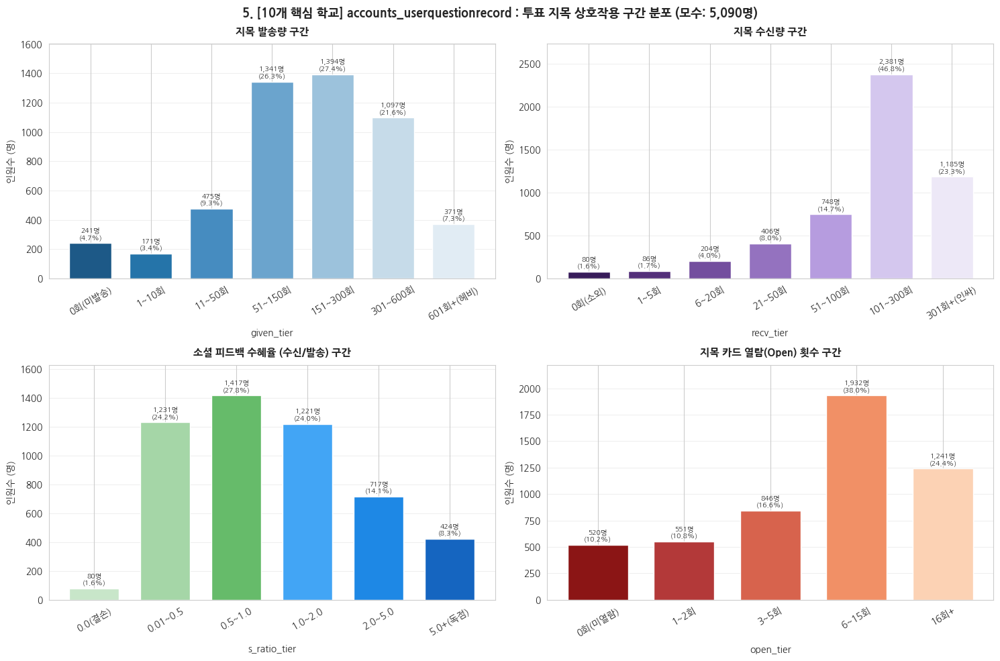

,current_school_id,사용자 수
0,271.0000,492
1,352.0000,491
2,369.0000,578
3,"1,478.0000",488
4,"1,719.0000",551
5,"4,426.0000",487
6,"4,516.0000",510
7,"5,372.0000",507
8,"5,491.0000",486
9,"5,520.0000",500


In [ ]:
# Ping 발신·수신·힌트 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('5. [10개 핵심 학교] accounts_userquestionrecord : 투표 지목 상호작용 구간 분포 분석')
print('=' * 70)
value_df_u = value_read_clean('mart_user_acquisition_profile_v2', usecols=['user_id', 'current_school_id', 'contacts_count_source'])
value_top10_schools = value_df_u['current_school_id'].value_counts().head(10).index.tolist()
value_cohort = set(value_df_u[value_df_u['current_school_id'].isin(value_top10_schools)]['user_id'].tolist())
value_total_cohort = len(value_cohort)
value_df_vote = value_read_clean('mart_vote_record_v2')
value_given_s = value_df_vote[value_df_vote['voter_user_id'].isin(value_cohort)].groupby('voter_user_id').size()
value_recv_s = value_df_vote[value_df_vote['chosen_user_id'].isin(value_cohort)].groupby('chosen_user_id').size()
value_open_s = value_df_vote[value_df_vote['chosen_user_id'].isin(value_cohort) & (value_df_vote['ping_opened_times_current'] > 0)].groupby('chosen_user_id').size()
value_df_c = pd.DataFrame({'user_id': list(value_cohort)})
value_df_c['given'] = value_df_c['user_id'].map(value_given_s).fillna(0)
value_df_c['recv'] = value_df_c['user_id'].map(value_recv_s).fillna(0)
value_df_c['open'] = value_df_c['user_id'].map(value_open_s).fillna(0)
value_df_c['s_ratio'] = value_df_c['recv'] / (value_df_c['given'] + 1)
value_g_bins = [-1, 0, 10, 50, 150, 300, 600, np.inf]
value_g_labels = ['0회(미발송)', '1~10회', '11~50회', '51~150회', '151~300회', '301~600회', '601회+(헤비)']
value_df_c['given_tier'] = pd.cut(value_df_c['given'], bins=value_g_bins, labels=value_g_labels)
value_rec_bins = [-1, 0, 5, 20, 50, 100, 300, np.inf]
value_rec_labels = ['0회(소외)', '1~5회', '6~20회', '21~50회', '51~100회', '101~300회', '301회+(인싸)']
value_df_c['recv_tier'] = pd.cut(value_df_c['recv'], bins=value_rec_bins, labels=value_rec_labels)
value_sr_bins = [-np.inf, 0.001, 0.5, 1.0, 2.0, 5.0, np.inf]
value_sr_labels = ['0.0(결손)', '0.01~0.5', '0.5~1.0', '1.0~2.0', '2.0~5.0', '5.0+(독점)']
value_df_c['s_ratio_tier'] = pd.cut(value_df_c['s_ratio'], bins=value_sr_bins, labels=value_sr_labels)
value_op_bins = [-1, 0, 2, 5, 15, np.inf]
value_op_labels = ['0회(미열람)', '1~2회', '3~5회', '6~15회', '16회+']
value_df_c['open_tier'] = pd.cut(value_df_c['open'], bins=value_op_bins, labels=value_op_labels)
print(f'- 10개 핵심 학교 코호트 모수: {value_total_cohort:,}명')
print('\n[지목 발송량 구간 (given_tier)]')
print(value_df_c['given_tier'].value_counts().reindex(value_g_labels, fill_value=0).to_frame('인원(명)'))
print('\n[지목 수신량 구간 (recv_tier)]')
print(value_df_c['recv_tier'].value_counts().reindex(value_rec_labels, fill_value=0).to_frame('인원(명)'))
print('\n[소셜 피드백 수혜율 구간 (s_ratio_tier)]')
print(value_df_c['s_ratio_tier'].value_counts().reindex(value_sr_labels, fill_value=0).to_frame('인원(명)'))
print('\n[힌트를 연 지목 카드 수 구간 (open_tier)]')
print(value_df_c['open_tier'].value_counts().reindex(value_op_labels, fill_value=0).to_frame('인원(명)'))
value_fig, value_axes = plt.subplots(2, 2, figsize=(15, 10))
value_fig.suptitle(f'5. [10개 핵심 학교] accounts_userquestionrecord : 투표 지목 상호작용 구간 분포 (모수: {value_total_cohort:,}명)', fontsize=13, weight='bold', y=0.98)
value_palette_g = ['#1d5987', '#2574a9', '#468cc0', '#6ba4cd', '#9cc2dc', '#c6dbe9', '#e1ecf4']
value_palette_rc = ['#381c5a', '#54307a', '#734e9e', '#9472bf', '#b69cdf', '#d4c7ee', '#ede8f7']
value_palette_sr = ['#c8e6c9', '#a5d6a7', '#66bb6a', '#42a5f5', '#1e88e5', '#1565c0']
value_palette_op = ['#8b1515', '#b33939', '#d7634d', '#f19066', '#fcd2b4']
value_g_counts = value_df_c['given_tier'].value_counts().reindex(value_g_labels, fill_value=0)
value_bars1 = value_axes[0, 0].bar(value_g_labels, value_g_counts, color=value_palette_g, width=0.7)
value_axes[0, 0].set_title('지목 발송량 구간', fontsize=11, weight='bold', pad=10)
value_axes[0, 0].set_xlabel('given_tier', fontsize=10, labelpad=8)
value_axes[0, 0].set_ylabel('인원수 (명)', fontsize=10)
value_axes[0, 0].set_ylim(0, max(value_g_counts) * 1.15)
value_axes[0, 0].tick_params(axis='x', rotation=30)
value_axes[0, 0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_axes[0, 0].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_rc_counts = value_df_c['recv_tier'].value_counts().reindex(value_rec_labels, fill_value=0)
value_bars2 = value_axes[0, 1].bar(value_rec_labels, value_rc_counts, color=value_palette_rc, width=0.7)
value_axes[0, 1].set_title('지목 수신량 구간', fontsize=11, weight='bold', pad=10)
value_axes[0, 1].set_xlabel('recv_tier', fontsize=10, labelpad=8)
value_axes[0, 1].set_ylabel('인원수 (명)', fontsize=10)
value_axes[0, 1].set_ylim(0, max(value_rc_counts) * 1.15)
value_axes[0, 1].tick_params(axis='x', rotation=30)
value_axes[0, 1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_axes[0, 1].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_sr_counts = value_df_c['s_ratio_tier'].value_counts().reindex(value_sr_labels, fill_value=0)
value_bars3 = value_axes[1, 0].bar(value_sr_labels, value_sr_counts, color=value_palette_sr, width=0.7)
value_axes[1, 0].set_title('Ping 수신 비율 (수신/(발신+1)) 구간', fontsize=11, weight='bold', pad=10)
value_axes[1, 0].set_xlabel('s_ratio_tier', fontsize=10, labelpad=8)
value_axes[1, 0].set_ylabel('인원수 (명)', fontsize=10)
value_axes[1, 0].set_ylim(0, max(value_sr_counts) * 1.15)
value_axes[1, 0].tick_params(axis='x', rotation=30)
value_axes[1, 0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars3:
    value_h = value_b.get_height()
    value_axes[1, 0].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_op_counts = value_df_c['open_tier'].value_counts().reindex(value_op_labels, fill_value=0)
value_bars4 = value_axes[1, 1].bar(value_op_labels, value_op_counts, color=value_palette_op, width=0.7)
value_axes[1, 1].set_title('힌트를 연 지목 카드 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[1, 1].set_xlabel('open_tier', fontsize=10, labelpad=8)
value_axes[1, 1].set_ylabel('인원수 (명)', fontsize=10)
value_axes[1, 1].set_ylim(0, max(value_op_counts) * 1.15)
value_axes[1, 1].tick_params(axis='x', rotation=30)
value_axes[1, 1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars4:
    value_h = value_b.get_height()
    value_axes[1, 1].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_cohort_audit = value_df_u[value_df_u.current_school_id.isin(value_top10_schools)].groupby("current_school_id").size().rename("사용자 수").reset_index()
display(value_cohort_audit)


- 10개 학교 5,090명 중 Ping 미발송자는 241명, 미수신자는 80명, 힌트 열람 기록이 없는 사용자는 520명이다.
- 이 표는 누적 행동 분포이며, 수신 이후 힌트 열람으로 전환한 비율을 측정한 것은 아니다.



6 & 7. [10개 핵심 학교] 경제 활동(포인트/결제) 및 연락처 동기화 구간 분포


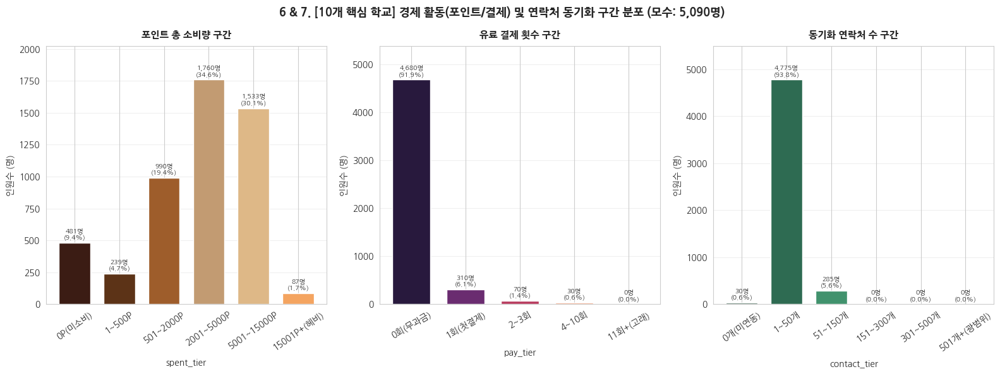

In [ ]:
# 하트 소비·결제·연락처 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('6 & 7. [10개 핵심 학교] 경제 활동(포인트/결제) 및 연락처 동기화 구간 분포')
print('=' * 70)
value_df_pay_mart = value_read_clean('mart_point_payment_event')
value_df_pay_c = value_df_pay_mart[value_df_pay_mart['user_id'].isin(value_cohort)]
value_spent_s = value_df_pay_c[value_df_pay_c['event_type'] == 'POINT_SPEND'].groupby('user_id')['point_amount_abs'].sum()
value_pay_s = value_df_pay_c[value_df_pay_c['event_type'] == 'PAYMENT_SUCCESS'].groupby('user_id').size()
value_df_c['spent'] = value_df_c['user_id'].map(value_spent_s).fillna(0)
value_df_c['pay_count'] = value_df_c['user_id'].map(value_pay_s).fillna(0)
value_contacts_map = value_df_u[value_df_u['user_id'].isin(value_cohort)].set_index('user_id')['contacts_count_source']
value_df_c['contacts'] = pd.to_numeric(value_df_c['user_id'].map(value_contacts_map), errors='coerce').fillna(0)
value_s_bins = [-1, 0, 500, 2000, 5000, 15000, np.inf]
value_s_labels = ['0P(미소비)', '1~500P', '501~2000P', '2001~5000P', '5001~15000P', '15001P+(헤비)']
value_df_c['spent_tier'] = pd.cut(value_df_c['spent'], bins=value_s_bins, labels=value_s_labels)
value_p_bins67 = [-1, 0, 1, 3, 10, np.inf]
value_p_labels67 = ['0회(무과금)', '1회(첫결제)', '2~3회', '4~10회', '11회+(고래)']
value_df_c['pay_tier_67'] = pd.cut(value_df_c['pay_count'], bins=value_p_bins67, labels=value_p_labels67)
value_c_bins = [-1, 0, 50, 150, 300, 500, np.inf]
value_c_labels = ['0개(미연동)', '1~50개', '51~150개', '151~300개', '301~500개', '501개+(광범위)']
value_df_c['contact_tier'] = pd.cut(value_df_c['contacts'], bins=value_c_bins, labels=value_c_labels)
value_fig, value_axes = plt.subplots(1, 3, figsize=(16, 6))
value_fig.suptitle('6 & 7. [10개 핵심 학교] 경제 활동(포인트/결제) 및 연락처 동기화 구간 분포 (모수: 5,090명)', fontsize=13, weight='bold', y=0.98)
value_palette_sp = ['#3b1c14', '#5c3317', '#9e5d2b', '#c29b72', '#deb887', '#f4a460']
value_palette_pay = ['#28193d', '#6a2c70', '#b83b5e', '#f08a5d', '#ee5253']
value_palette_ct = ['#234d3b', '#2e6b52', '#41926d', '#67b992', '#97d6b8', '#c8eedb']
value_sp_counts = value_df_c['spent_tier'].value_counts().reindex(value_s_labels, fill_value=0)
value_bars1 = value_axes[0].bar(value_s_labels, value_sp_counts, color=value_palette_sp, width=0.7)
value_axes[0].set_title('포인트 총 소비량 구간', fontsize=11, weight='bold', pad=10)
value_axes[0].set_xlabel('spent_tier', fontsize=10, labelpad=8)
value_axes[0].set_ylabel('인원수 (명)', fontsize=10)
value_axes[0].set_ylim(0, max(value_sp_counts) * 1.15)
value_axes[0].tick_params(axis='x', rotation=35)
value_axes[0].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_axes[0].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_py_counts = value_df_c['pay_tier_67'].value_counts().reindex(value_p_labels67, fill_value=0)
value_bars2 = value_axes[1].bar(value_p_labels67, value_py_counts, color=value_palette_pay, width=0.7)
value_axes[1].set_title('유료 결제 횟수 구간', fontsize=11, weight='bold', pad=10)
value_axes[1].set_xlabel('pay_tier', fontsize=10, labelpad=8)
value_axes[1].set_ylabel('인원수 (명)', fontsize=10)
value_axes[1].set_ylim(0, max(value_py_counts) * 1.15)
value_axes[1].tick_params(axis='x', rotation=30)
value_axes[1].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_axes[1].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
value_ct_counts = value_df_c['contact_tier'].value_counts().reindex(value_c_labels, fill_value=0)
value_bars3 = value_axes[2].bar(value_c_labels, value_ct_counts, color=value_palette_ct, width=0.7)
value_axes[2].set_title('동기화 연락처 수 구간', fontsize=11, weight='bold', pad=10)
value_axes[2].set_xlabel('contact_tier', fontsize=10, labelpad=8)
value_axes[2].set_ylabel('인원수 (명)', fontsize=10)
value_axes[2].set_ylim(0, max(value_ct_counts) * 1.15)
value_axes[2].tick_params(axis='x', rotation=35)
value_axes[2].grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars3:
    value_h = value_b.get_height()
    value_axes[2].annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7.5, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
value_drop('value_df_pay_mart', 'value_df_pay_c', 'value_spent_s', 'value_pay_s', 'value_contacts_map')


- 하트 소비·현금 결제·연락처 동기화를 구분해 집계했다. 보상 하트도 소비할 수 있으므로 하트 사용량을 결제 경험으로 해석하지 않는다.


### 3-5-3. 군집 입력 지표

- 소통 반응, 발송 대비 Ping 수신 비율, 힌트 열람 비율, 결제 횟수, 친구 요청 수신 비중을 사용자별로 구성했다.



8. [10개 핵심 학교] 5개 핵심 비율·행동 피처 구간별 유저 분포 현황


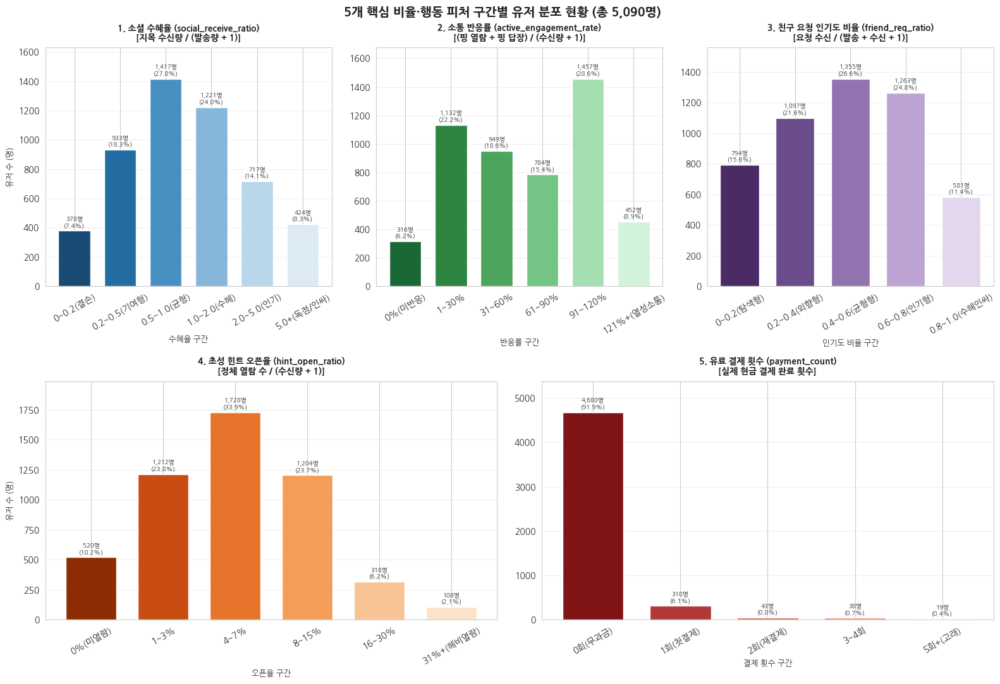


행동 분포 분석 완료. 표와 차트는 화면에만 표시했습니다.


In [ ]:
# 군집 후보 지표 분포
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('8. [10개 핵심 학교] 5개 핵심 비율·행동 피처 구간별 유저 분포 현황')
print('=' * 70)
value_df_v_recv = value_df_vote[value_df_vote['chosen_user_id'].isin(value_cohort)]
value_ping_read_s = value_df_v_recv[value_df_v_recv['ping_has_read_current'] == 1].groupby('chosen_user_id').size()
value_ping_reply_s = value_df_v_recv[value_df_v_recv['ping_answer_status_current'] == 'A'].groupby('chosen_user_id').size()
value_opened_times_s = value_df_v_recv[value_df_v_recv['ping_opened_times_current'] > 0].groupby('chosen_user_id').size()
value_df_c['ping_read'] = value_df_c['user_id'].map(value_ping_read_s).fillna(0)
value_df_c['ping_reply'] = value_df_c['user_id'].map(value_ping_reply_s).fillna(0)
value_df_c['opened_times'] = value_df_c['user_id'].map(value_opened_times_s).fillna(0)
value_df_fr = value_read_clean('mart_user_viral_profile_v2', usecols=['user_id', 'sent_request_count', 'received_request_count'])
value_df_fr_c = value_df_fr[value_df_fr['user_id'].isin(value_cohort)].set_index('user_id')
value_df_c['friend_req_sent'] = value_df_c['user_id'].map(value_df_fr_c['sent_request_count']).fillna(0)
value_df_c['friend_req_received'] = value_df_c['user_id'].map(value_df_fr_c['received_request_count']).fillna(0)
value_df_c['social_receive_ratio'] = value_df_c['recv'] / (value_df_c['given'] + 1)
value_df_c['active_engagement_rate'] = (value_df_c['ping_read'] + value_df_c['ping_reply']) / (value_df_c['recv'] + 1) * 100
value_df_c['friend_req_ratio'] = value_df_c['friend_req_received'] / (value_df_c['friend_req_sent'] + value_df_c['friend_req_received'] + 1)
value_df_c['hint_open_ratio'] = value_df_c['opened_times'] / (value_df_c['recv'] + 1) * 100
value_df_c['payment_count'] = value_df_c['pay_count']
value_srr_bins = [-np.inf, 0.2, 0.5, 1.0, 2.0, 5.0, np.inf]
value_srr_labels = ['0~0.2(결손)', '0.2~0.5(기여형)', '0.5~1.0(균형)', '1.0~2.0(수혜)', '2.0~5.0(인기)', '5.0+(독점/인싸)']
value_df_c['srr_tier'] = pd.cut(value_df_c['social_receive_ratio'], bins=value_srr_bins, labels=value_srr_labels, right=True)
value_aer_bins = [-np.inf, 0.001, 30.0, 60.0, 90.0, 120.0, np.inf]
value_aer_labels = ['0%(미반응)', '1~30%', '31~60%', '61~90%', '91~120%', '121%+(열성소통)']
value_df_c['aer_tier'] = pd.cut(value_df_c['active_engagement_rate'], bins=value_aer_bins, labels=value_aer_labels, right=True)
value_frr_bins = [-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf]
value_frr_labels = ['0~0.2(탐색형)', '0.2~0.4(외향형)', '0.4~0.6(균형형)', '0.6~0.8(인기형)', '0.8~1.0(수혜인싸)']
value_df_c['frr_tier'] = pd.cut(value_df_c['friend_req_ratio'], bins=value_frr_bins, labels=value_frr_labels, right=True)
value_hor_bins = [-np.inf, 0.001, 3.0, 7.0, 15.0, 30.0, np.inf]
value_hor_labels = ['0%(미열람)', '1~3%', '4~7%', '8~15%', '16~30%', '31%+(헤비열람)']
value_df_c['hor_tier'] = pd.cut(value_df_c['hint_open_ratio'], bins=value_hor_bins, labels=value_hor_labels, right=True)
value_pay_bins_5 = [-1, 0, 1, 2, 4, np.inf]
value_pay_labels_5 = ['0회(무과금)', '1회(첫결제)', '2회(재결제)', '3~4회', '5회+(고래)']
value_df_c['pay_tier_5'] = pd.cut(value_df_c['payment_count'], bins=value_pay_bins_5, labels=value_pay_labels_5)
value_fig = plt.figure(figsize=(16, 11))
value_fig.suptitle('5개 핵심 비율·행동 피처 구간별 유저 분포 현황 (총 5,090명)', fontsize=14, weight='bold', y=0.98)
value_ax1 = plt.subplot2grid((2, 6), (0, 0), colspan=2)
value_ax2 = plt.subplot2grid((2, 6), (0, 2), colspan=2)
value_ax3 = plt.subplot2grid((2, 6), (0, 4), colspan=2)
value_ax4 = plt.subplot2grid((2, 6), (1, 0), colspan=3)
value_ax5 = plt.subplot2grid((2, 6), (1, 3), colspan=3)
value_c1 = value_df_c['srr_tier'].value_counts().reindex(value_srr_labels, fill_value=0)
value_bars1 = value_ax1.bar(value_srr_labels, value_c1, color=['#1a4b75', '#246da3', '#4990c2', '#86b7db', '#b9d6ea', '#dceaf3'], width=0.7)
value_ax1.set_title('1. 소셜 수혜율 (social_receive_ratio)\n[지목 수신량 / (발송량 + 1)]', fontsize=10, weight='bold', pad=8)
value_ax1.set_xlabel('수혜율 구간', fontsize=9)
value_ax1.set_ylabel('유저 수 (명)', fontsize=9)
value_ax1.set_ylim(0, max(value_c1) * 1.15)
value_ax1.tick_params(axis='x', rotation=30)
value_ax1.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars1:
    value_h = value_b.get_height()
    value_ax1.annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7, xytext=(0, 2), textcoords='offset points')
value_c2 = value_df_c['aer_tier'].value_counts().reindex(value_aer_labels, fill_value=0)
value_bars2 = value_ax2.bar(value_aer_labels, value_c2, color=['#1b6837', '#2e8540', '#4ba55d', '#74c485', '#a3dfb0', '#d2f3db'], width=0.7)
value_ax2.set_title('2. 소통 반응률 (active_engagement_rate)\n[(핑 열람 + 핑 답장) / (수신량 + 1)]', fontsize=10, weight='bold', pad=8)
value_ax2.set_xlabel('반응률 구간', fontsize=9)
value_ax2.set_ylim(0, max(value_c2) * 1.15)
value_ax2.tick_params(axis='x', rotation=30)
value_ax2.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars2:
    value_h = value_b.get_height()
    value_ax2.annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7, xytext=(0, 2), textcoords='offset points')
value_c3 = value_df_c['frr_tier'].value_counts().reindex(value_frr_labels, fill_value=0)
value_bars3 = value_ax3.bar(value_frr_labels, value_c3, color=['#4a2b66', '#6b4c8a', '#9173b0', '#bca3d4', '#e2d7ed'], width=0.7)
value_ax3.set_title('3. 친구 요청 인기도 비율 (friend_req_ratio)\n[요청 수신 / (발송 + 수신 + 1)]', fontsize=10, weight='bold', pad=8)
value_ax3.set_xlabel('인기도 비율 구간', fontsize=9)
value_ax3.set_ylim(0, max(value_c3) * 1.15)
value_ax3.tick_params(axis='x', rotation=30)
value_ax3.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars3:
    value_h = value_b.get_height()
    value_ax3.annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7, xytext=(0, 2), textcoords='offset points')
value_c4 = value_df_c['hor_tier'].value_counts().reindex(value_hor_labels, fill_value=0)
value_bars4 = value_ax4.bar(value_hor_labels, value_c4, color=['#8c2d04', '#c94d12', '#e67329', '#f39e58', '#f8c495', '#fde2cb'], width=0.7)
value_ax4.set_title('4. 초성 힌트 오픈율 (hint_open_ratio)\n[정체 열람 수 / (수신량 + 1)]', fontsize=10, weight='bold', pad=8)
value_ax4.set_xlabel('오픈율 구간', fontsize=9)
value_ax4.set_ylabel('유저 수 (명)', fontsize=9)
value_ax4.set_ylim(0, max(value_c4) * 1.15)
value_ax4.tick_params(axis='x', rotation=30)
value_ax4.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars4:
    value_h = value_b.get_height()
    value_ax4.annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7, xytext=(0, 2), textcoords='offset points')
value_c5 = value_df_c['pay_tier_5'].value_counts().reindex(value_pay_labels_5, fill_value=0)
value_bars5 = value_ax5.bar(value_pay_labels_5, value_c5, color=['#801414', '#b33939', '#d7634d', '#f19066', '#fcd2b4'], width=0.7)
value_ax5.set_title('5. 유료 결제 횟수 (payment_count)\n[실제 현금 결제 완료 횟수]', fontsize=10, weight='bold', pad=8)
value_ax5.set_xlabel('결제 횟수 구간', fontsize=9)
value_ax5.set_ylim(0, max(value_c5) * 1.15)
value_ax5.tick_params(axis='x', rotation=30)
value_ax5.grid(axis='y', linestyle='-', alpha=0.3, color='#cccccc')
for value_b in value_bars5:
    value_h = value_b.get_height()
    value_ax5.annotate(f'{int(value_h):,}명\n({value_h / value_total_cohort * 100:.1f}%)', (value_b.get_x() + value_b.get_width() / 2.0, value_h), ha='center', va='bottom', fontsize=7, xytext=(0, 2), textcoords='offset points')
plt.tight_layout()
plt.show()
plt.close()
print('\n' + '=' * 70)
print('행동 지표 분포')
print('=' * 70)
value_eda_reference = value_df_c.rename(columns={'given': 'votes_given', 'recv': 'votes_received'}).copy()
value_eda_reference['active_engagement_rate'] /= 100.0
value_eda_reference['hint_open_ratio'] /= 100.0

value_drop('value_df_v_recv', 'value_df_fr', 'value_df_fr_c', 'value_df_vote', 'value_df_u')


- 소통 반응 지표에는 읽기와 답장이 함께 포함된다.
- Ping 수신 비율은 수신 건수 ÷ (발신 건수 + 1)로, 1보다 클 수 있다. 높은 비율을 높은 절대 수신량으로 해석하지 않는다.


In [ ]:
# 사용자 단위 분석표
koreanize_matplotlib.koreanize()
value_df_prev_top10 = value_eda_reference.copy()
value_core_users = set(value_df_prev_top10['user_id'].tolist())
value_df_user_acq = value_read_clean('mart_user_acquisition_profile_v2', usecols=['user_id', 'current_school_id', 'gender', 'current_grade', 'contacts_count_source'])
value_df_user_acq['user_id'] = pd.to_numeric(value_df_user_acq['user_id'], errors='coerce')
value_mart = value_df_user_acq[value_df_user_acq['user_id'].isin(value_core_users)].copy()
value_mart.rename(columns={'current_school_id': 'school_id', 'current_grade': 'grade', 'contacts_count_source': 'contacts_count'}, inplace=True)
value_mart['contacts_count'] = pd.to_numeric(value_mart['contacts_count'], errors='coerce').fillna(0)
value_mart['grade'] = pd.to_numeric(value_mart['grade'], errors='coerce')
value_df_vote = value_read_clean('mart_vote_record_v2', usecols=['user_question_record_id', 'voter_user_id', 'chosen_user_id', 'ping_has_read_current', 'ping_answer_status_current', 'ping_opened_times_current'])
value_df_vote['voter_user_id'] = pd.to_numeric(value_df_vote['voter_user_id'], errors='coerce')
value_df_vote['chosen_user_id'] = pd.to_numeric(value_df_vote['chosen_user_id'], errors='coerce')
value_voter_agg = value_df_vote.groupby('voter_user_id').size().reset_index(name='votes_given').rename(columns={'voter_user_id': 'user_id'})
value_mart = value_mart.merge(value_voter_agg, on='user_id', how='left').fillna({'votes_given': 0})
value_df_vote['ping_has_read'] = pd.to_numeric(value_df_vote['ping_has_read_current'], errors='coerce').fillna(0).astype(int)
value_df_vote['ping_reply'] = (value_df_vote['ping_answer_status_current'] == 'A').astype(int)
value_df_vote['opened_times_sum'] = pd.to_numeric(value_df_vote['ping_opened_times_current'], errors='coerce').fillna(0)
value_rec_agg = value_df_vote.groupby('chosen_user_id').agg(votes_received=('user_question_record_id', 'count'), ping_read=('ping_has_read', 'sum'), ping_reply=('ping_reply', 'sum'), opened_times=('opened_times_sum', 'sum')).reset_index().rename(columns={'chosen_user_id': 'user_id'})
value_mart = value_mart.merge(value_rec_agg, on='user_id', how='left').fillna({'votes_received': 0, 'ping_read': 0, 'ping_reply': 0, 'opened_times': 0})
value_df_viral = value_read_clean('mart_user_viral_profile_v2', usecols=['user_id', 'sent_request_count', 'received_request_count'])
value_df_viral['user_id'] = pd.to_numeric(value_df_viral['user_id'], errors='coerce')
value_df_viral.rename(columns={'sent_request_count': 'friend_req_sent', 'received_request_count': 'friend_req_received'}, inplace=True)
value_mart = value_mart.merge(value_df_viral, on='user_id', how='left').fillna({'friend_req_sent': 0, 'friend_req_received': 0})
value_df_val = value_read_clean('mart_value_event_v2', usecols=['service_user_id', 'event_type', 'point_amount_abs'])
value_df_val['user_id'] = pd.to_numeric(value_df_val['service_user_id'], errors='coerce')
value_df_val['point_amount_abs_num'] = pd.to_numeric(value_df_val['point_amount_abs'], errors='coerce').fillna(0)
value_pt_spent = value_df_val[value_df_val['event_type'] == 'POINT_SPEND'].groupby('user_id')['point_amount_abs_num'].sum().reset_index(name='point_spent')
value_mart = value_mart.merge(value_pt_spent, on='user_id', how='left').fillna({'point_spent': 0})
value_pay_agg = value_df_val[value_df_val['event_type'] == 'PAYMENT_SUCCESS'].groupby('user_id').size().reset_index(name='payment_count')
value_mart = value_mart.merge(value_pay_agg, on='user_id', how='left').fillna({'payment_count': 0})
value_mart['is_paying_user'] = (value_mart['payment_count'] > 0).astype(int)
value_df_att = value_read_clean('mart_attendance_record_v2', usecols=['user_id', 'attendance_list_length'])
value_df_att['user_id'] = pd.to_numeric(value_df_att['user_id'], errors='coerce')
value_df_att['attendance_days'] = pd.to_numeric(value_df_att['attendance_list_length'], errors='coerce').fillna(0)
value_mart = value_mart.merge(value_df_att[['user_id', 'attendance_days']], on='user_id', how='left').fillna({'attendance_days': 0})
value_mart['active_engagement_rate'] = (value_mart['ping_read'] + value_mart['ping_reply']) / (value_mart['votes_received'] + 1.0)
value_mart['social_receive_ratio'] = value_mart['votes_received'] / (value_mart['votes_given'] + 1.0)
value_mart['hint_open_ratio'] = value_mart['opened_times'] / (value_mart['votes_received'] + 1.0)
value_mart['friend_req_ratio'] = value_mart['friend_req_received'] / (value_mart['friend_req_sent'] + value_mart['friend_req_received'] + 1.0)
assert value_mart.user_id.is_unique, '사용자별 지표가 중복되었습니다.'
assert set(value_mart.user_id) == value_cohort
print(f'군집용 지표 구성 완료: {len(value_mart):,}명, {len(value_mart.columns)}열')
display(value_mart.head())

value_drop('value_df_user_acq', 'value_df_vote', 'value_df_viral', 'value_df_val', 'value_df_att', 'value_voter_agg', 'value_rec_agg', 'value_pt_spent', 'value_pay_agg')


군집용 지표 구성 완료: 5,090명, 20열


,user_id,gender,grade,school_id,contacts_count,votes_given,votes_received,ping_read,ping_reply,opened_times,friend_req_sent,friend_req_received,point_spent,payment_count,is_paying_user,attendance_days,active_engagement_rate,social_receive_ratio,hint_open_ratio,friend_req_ratio
0,838023,F,1.0000,271.0000,0.0000,22.0000,262.0000,0.0000,0.0000,2.0000,0,48,600.0000,0.0000,0,0.0000,0.0000,11.3913,0.0076,0.9796
1,838466,F,2.0000,369.0000,0.0000,131.0000,343.0000,19.0000,0.0000,13.0000,1,67,"3,800.0000",0.0000,0,0.0000,0.0552,2.5985,0.0378,0.9710
2,838642,F,2.0000,271.0000,0.0000,10.0000,40.0000,10.0000,1.0000,1.0000,1,70,300.0000,0.0000,0,0.0000,0.2683,3.6364,0.0244,0.9722
3,839357,M,1.0000,271.0000,0.0000,212.0000,173.0000,15.0000,0.0000,6.0000,12,68,"1,700.0000",0.0000,0,0.0000,0.0862,0.8122,0.0345,0.8395
4,839670,F,2.0000,271.0000,0.0000,0.0000,41.0000,0.0000,0.0000,0.0000,0,30,0.0000,0.0000,0,0.0000,0.0000,41.0000,0.0000,0.9677


- 5,090명의 발신·수신·힌트·결제 등 행동을 사용자당 한 행, 20개 열로 구성했다.


- 비활동 유저 분리 후 클러스터링 학습 코어 유저 수: 4,849명 (비활동 241명 분리 완료)


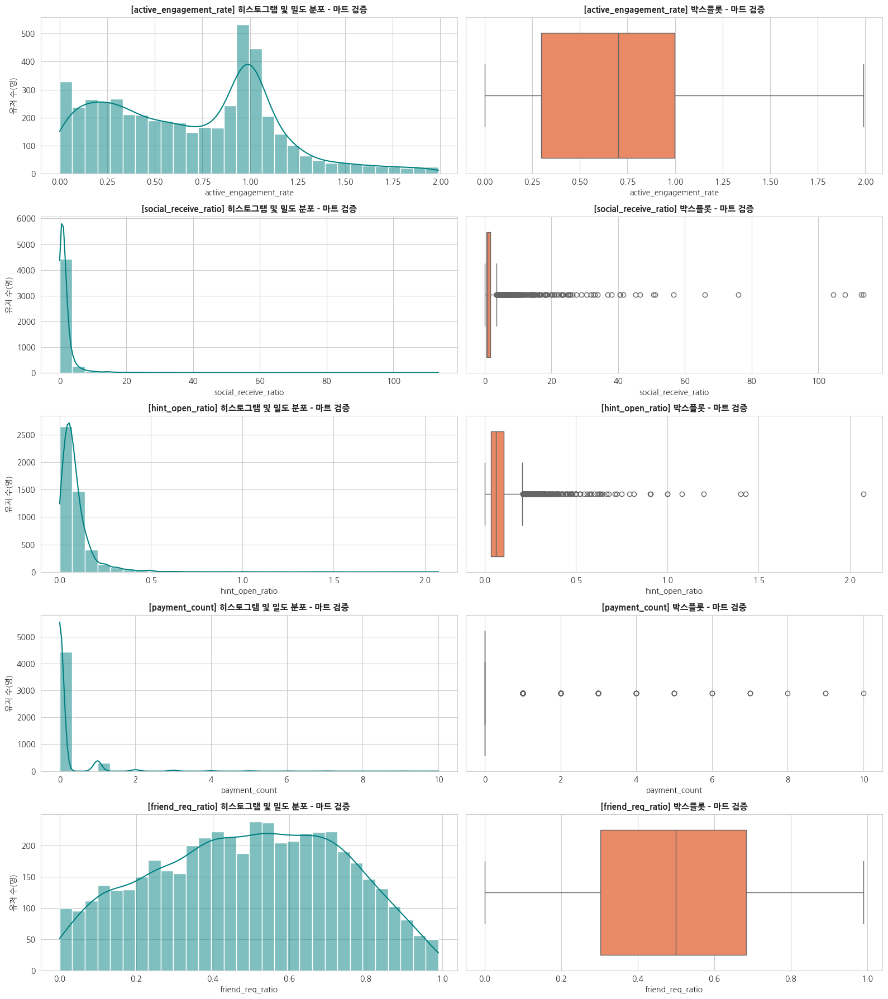


=== 5대 핵심 피처 기초 통계량 (투표 코어 4,849명) ===
       active_engagement_rate  social_receive_ratio  hint_open_ratio  payment_count  friend_req_ratio
count              4,849.0000            4,849.0000       4,849.0000     4,849.0000        4,849.0000
mean                   0.6861                1.8510           0.0856         0.1326            0.4900
std                    0.4382                4.7815           0.0978         0.5826            0.2433
min                    0.0000                0.0000           0.0000         0.0000            0.0000
25%                    0.2955                0.4884           0.0347         0.0000            0.3030
50%                    0.7029                0.8954           0.0630         0.0000            0.5000
75%                    0.9973                1.6949           0.1036         0.0000            0.6835
max                    1.9900              113.5000           2.0741        10.0000            0.9900

=== 앞선 EDA 집계 vs 군집용 마트 피처 평균 비교 ===
    

,EDA 집계 평균,군집용 마트 평균,차이(Diff),일치
active_engagement_rate,0.6861,0.6861,0.0000,True
social_receive_ratio,1.8510,1.8510,0.0000,True
friend_req_ratio,0.4900,0.4900,0.0000,True
payment_count,0.1326,0.1326,0.0000,True


힌트 비율의 차이는 카드 수와 열람 횟수 합계라는 원본 정의의 차이입니다.


In [ ]:
# 투표 참여자 선별·지표 대사
koreanize_matplotlib.koreanize()
value_core_df = value_mart[value_mart['votes_given'] > 0].copy().reset_index(drop=True)
print(f'- 투표 미발신자 제외 후 군집 대상: {len(value_core_df):,}명 (미발신자 241명 제외)')
value_features_5 = ['active_engagement_rate', 'social_receive_ratio', 'hint_open_ratio', 'payment_count', 'friend_req_ratio']
value_fig, value_axes = plt.subplots(len(value_features_5), 2, figsize=(16, 18))
for value_i, value_col in enumerate(value_features_5):
    sns.histplot(value_core_df[value_col], kde=True, ax=value_axes[value_i, 0], color='teal', bins=30)
    value_axes[value_i, 0].set_title(f'[{value_col}] 히스토그램 및 밀도 분포 - 마트 검증', fontsize=11, weight='bold')
    value_axes[value_i, 0].set_ylabel('유저 수(명)')
    sns.boxplot(x=value_core_df[value_col], ax=value_axes[value_i, 1], color='coral')
    value_axes[value_i, 1].set_title(f'[{value_col}] 박스플롯 - 마트 검증', fontsize=11, weight='bold')
plt.tight_layout()
plt.show()
plt.close()
print('\n=== 5대 핵심 피처 기초 통계량 (투표 코어 4,849명) ===')
print(value_core_df[value_features_5].describe().round(4).to_string())
value_raw_core = value_df_prev_top10[value_df_prev_top10['votes_given'] > 0].copy().reset_index(drop=True)
print('\n=== 앞선 EDA 집계 vs 군집용 마트 피처 평균 비교 ===')
value_comp_df = pd.DataFrame({'EDA 집계 평균': value_raw_core[value_features_5].mean(), '군집용 마트 평균': value_core_df[value_features_5].mean(), '차이(Diff)': (value_core_df[value_features_5].mean() - value_raw_core[value_features_5].mean()).abs()})
print(value_comp_df.round(6).to_string())
print('\n=== 군집 입력 지표 비교 ===')
value_comparable = ['active_engagement_rate', 'social_receive_ratio', 'friend_req_ratio', 'payment_count']
value_feature_audit = value_comp_df.loc[value_comparable].copy()
value_feature_audit['일치'] = value_feature_audit['차이(Diff)'].abs() < 1e-9
display(value_feature_audit)
assert value_feature_audit['일치'].all(), 'EDA와 군집용 지표 집계가 다릅니다.'
print('힌트 비율은 카드 수와 열람 횟수 합계의 집계 단위 차이가 있습니다.')

value_drop('value_df_prev_top10', 'value_raw_core', 'value_core_df')


- 투표 발신자 4,849명을 군집 대상으로 사용하고 미발신자 241명은 제외했다. 발송 대비 수신 비율의 평균은 1.85, 중앙값은 0.90이다.
- 탐색 분석은 힌트를 연 카드 수, 군집 지표는 열람 횟수 합계를 사용해 힌트 비율이 다르다. 나머지 네 지표의 평균은 일치했다.


In [ ]:
# 군집 입력 분위수 변환
koreanize_matplotlib.koreanize()
value_df_raw = value_mart.copy()
value_df_core = value_df_raw[value_df_raw['votes_given'] > 0].copy().reset_index(drop=True)
print(f'- 클러스터링 학습 대상 코어 유저 수: {len(value_df_core):,}명 (미발신자 {len(value_df_raw) - len(value_df_core):,}명 제외)')
value_features = ['active_engagement_rate', 'social_receive_ratio', 'hint_open_ratio', 'payment_count', 'friend_req_ratio']
value_X_raw = value_df_core[value_features].copy()
value_scaler = QuantileTransformer(output_distribution='normal', random_state=42)
value_X_scaled = value_scaler.fit_transform(value_X_raw)
print('- 5대 핵심 피처 QuantileTransformation 정규분포 변환 완료.')


- 클러스터링 학습 대상 코어 유저 수: 4,849명 (비활동 241명 분리)
- 5대 핵심 피처 QuantileTransformation 정규분포 변환 완료.


- 다섯 지표를 분위수 기반 정규분포로 변환해 극단값의 영향을 줄였다. 변환값은 실제 행동 횟수가 아닌 표본 내 상대적 위치를 나타낸다.


### 3-5-4. 사용자 유형

- 군집 수 2~6개의 적합도를 비교하고, 행동 특성을 네 군집으로 정리했다.



[GMM 군집 수(K=2~6) 6대 적합도 종합 평가]

             GMM 군집 모델 적합도 및 클러스터링 품질 종합 평가 결과표
 K          AIC          BIC Silhouette Fuzzy_Silhouette      NES     MMPP
 2     10,087.9     10,353.9     0.6207           0.6207   0.0000   1.0000
 3     -1,083.2       -681.0     0.6153           0.6153   0.0000   1.0000
 4     -1,586.2     -1,047.8     0.3048           0.3663   0.2363   0.8470
 5     -2,164.6     -1,490.0     0.2853           0.3414   0.1891   0.8611
 6     -3,171.6     -2,360.8     0.1645           0.1984   0.2982   0.7597


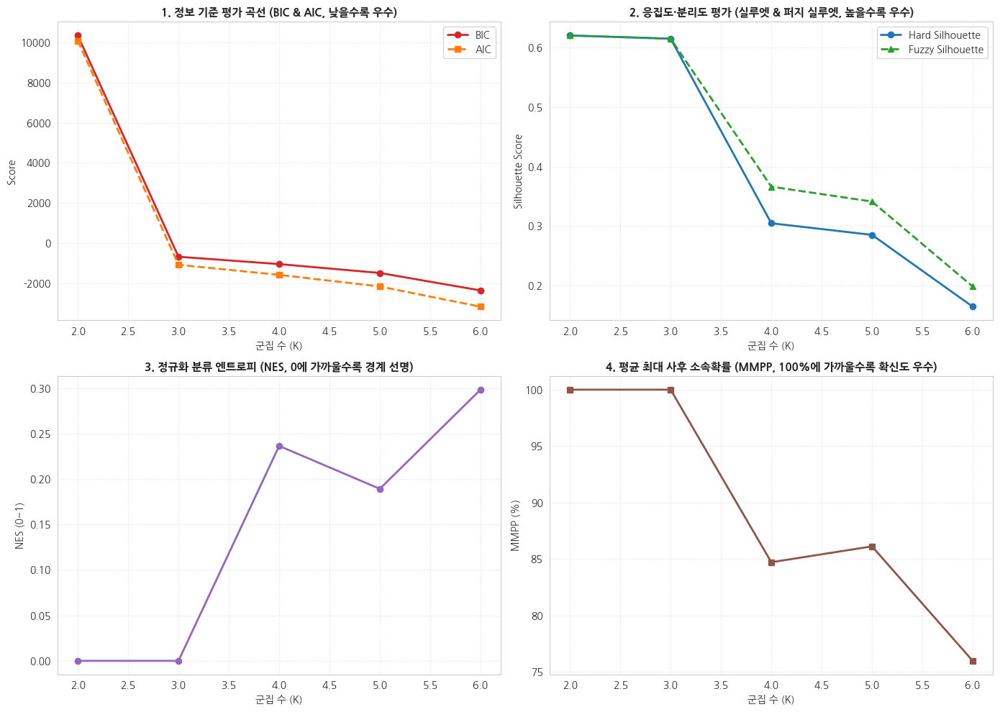

In [ ]:
# GMM 군집 수 비교
koreanize_matplotlib.koreanize()
value_eval_list = []
print('\n[GMM 군집 수(K=2~6) 6대 적합도 종합 평가]')
for value_k in range(2, 7):
    value_gmm = GaussianMixture(n_components=value_k, covariance_type='full', random_state=42, n_init=15)
    value_preds = value_gmm.fit_predict(value_X_scaled)
    value_probs = value_gmm.predict_proba(value_X_scaled)
    value_aic = value_gmm.aic(value_X_scaled)
    value_bic = value_gmm.bic(value_X_scaled)
    value_sil = silhouette_score(value_X_scaled, value_preds)
    value_max_probs = np.max(value_probs, axis=1)
    value_mmpp = np.mean(value_max_probs)
    value_eps = 1e-12
    value_probs_safe = np.clip(value_probs, value_eps, 1.0)
    value_entropy_per_sample = -np.sum(value_probs_safe * np.log(value_probs_safe), axis=1)
    value_pe = np.mean(value_entropy_per_sample)
    value_nes = value_pe / np.log(value_k)
    value_sorted_probs = np.sort(value_probs, axis=1)
    value_diff_top2 = value_sorted_probs[:, -1] - value_sorted_probs[:, -2]
    value_sil_samples = silhouette_samples(value_X_scaled, value_preds)
    value_fuzzy_sil = np.sum(value_diff_top2 * value_sil_samples) / np.sum(value_diff_top2)
    value_eval_list.append({'K': value_k, 'AIC': value_aic, 'BIC': value_bic, 'Silhouette': value_sil, 'Fuzzy_Silhouette': value_fuzzy_sil, 'NES': value_nes, 'MMPP': value_mmpp})
value_eval_df = pd.DataFrame(value_eval_list)
print('\n' + '=' * 85)
print('             GMM 군집 모델 적합도 및 클러스터링 품질 종합 평가 결과표')
print('=' * 85)
print(value_eval_df.to_string(index=False, formatters={'AIC': '{:>12,.1f}'.format, 'BIC': '{:>12,.1f}'.format, 'Silhouette': '{:>10.4f}'.format, 'Fuzzy_Silhouette': '{:>16.4f}'.format, 'NES': '{:>8.4f}'.format, 'MMPP': '{:>8.4f}'.format}))
print('=' * 85)
value_fig, value_axes = plt.subplots(2, 2, figsize=(14, 10))
value_axes[0, 0].plot(value_eval_df['K'], value_eval_df['BIC'], marker='o', color='#d62728', linewidth=2, label='BIC')
value_axes[0, 0].plot(value_eval_df['K'], value_eval_df['AIC'], marker='s', color='#ff7f0e', linewidth=2, linestyle='--', label='AIC')
value_axes[0, 0].set_title('1. 정보 기준 평가 곡선 (BIC & AIC, 낮을수록 우수)', fontsize=11, weight='bold')
value_axes[0, 0].set_xlabel('군집 수 (K)')
value_axes[0, 0].set_ylabel('Score')
value_axes[0, 0].legend()
value_axes[0, 0].grid(True, linestyle=':', alpha=0.6)
value_axes[0, 1].plot(value_eval_df['K'], value_eval_df['Silhouette'], marker='o', color='#1f77b4', linewidth=2, label='Hard Silhouette')
value_axes[0, 1].plot(value_eval_df['K'], value_eval_df['Fuzzy_Silhouette'], marker='^', color='#2ca02c', linewidth=2, linestyle='--', label='Fuzzy Silhouette')
value_axes[0, 1].set_title('2. 응집도·분리도 평가 (실루엣 & 퍼지 실루엣, 높을수록 우수)', fontsize=11, weight='bold')
value_axes[0, 1].set_xlabel('군집 수 (K)')
value_axes[0, 1].set_ylabel('Silhouette Score')
value_axes[0, 1].legend()
value_axes[0, 1].grid(True, linestyle=':', alpha=0.6)
value_axes[1, 0].plot(value_eval_df['K'], value_eval_df['NES'], marker='o', color='#9467bd', linewidth=2)
value_axes[1, 0].set_title('3. 정규화 분류 엔트로피 (NES, 0에 가까울수록 경계 선명)', fontsize=11, weight='bold')
value_axes[1, 0].set_xlabel('군집 수 (K)')
value_axes[1, 0].set_ylabel('NES (0~1)')
value_axes[1, 0].grid(True, linestyle=':', alpha=0.6)
value_axes[1, 1].plot(value_eval_df['K'], value_eval_df['MMPP'] * 100, marker='s', color='#8c564b', linewidth=2)
value_axes[1, 1].set_title('4. 평균 최대 사후 소속확률 (MMPP, 100%에 가까울수록 확신도 우수)', fontsize=11, weight='bold')
value_axes[1, 1].set_xlabel('군집 수 (K)')
value_axes[1, 1].set_ylabel('MMPP (%)')
value_axes[1, 1].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
plt.close()


- AIC·BIC는 군집 수가 늘수록 낮아지지만, 실루엣 점수는 K=2의 0.621에서 K=4의 0.305로 떨어진다. 네 군집은 여러 행동 유형을 살펴보기 위한 선택이며 모든 지표에서 최적인 값은 아니다.



=== [K=4 군집별 5대 핵심 피처 평균] ===
         인원수(명)   비율(%)  active_engagement_rate  social_receive_ratio  hint_open_ratio  payment_count  friend_req_ratio
cluster                                                                                                                
0          1518 31.3100                  1.0227                0.5182           0.1449         0.0000            0.4120
1          2630 54.2400                  0.4953                2.3955           0.0517         0.0000            0.5539
2           410  8.4600                  0.8835                1.1000           0.1444         1.5683            0.4807
3           291  6.0000                  0.3765                4.9403           0.0000         0.0000            0.3324

=== [K=4 군집별 원본 행동 지표 평균] ===
         인원수(명)   비율(%)  votes_given  votes_received  ping_read  opened_times  point_spent  payment_count  contacts_count
cluster                                                                                         

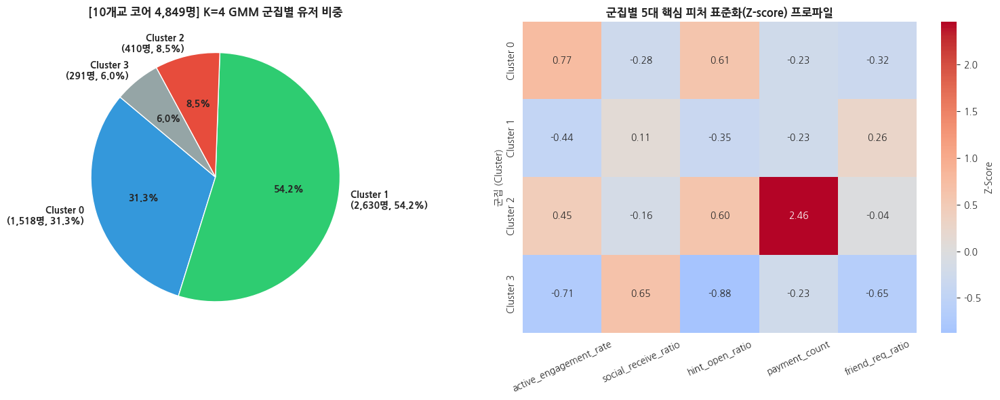


=== 5단계 GMM 유저 세그멘테이션 모델링 완료 ===


,user_id,gender,grade,school_id,contacts_count,votes_given,votes_received,ping_read,ping_reply,opened_times,friend_req_sent,friend_req_received,point_spent,payment_count,is_paying_user,attendance_days,active_engagement_rate,social_receive_ratio,hint_open_ratio,friend_req_ratio,cluster,cluster_prob_0,cluster_prob_1,cluster_prob_2,cluster_prob_3
0,838023,F,1.0000,271.0000,0.0000,22.0000,262.0000,0.0000,0.0000,2.0000,0,48,600.0000,0.0000,0,0.0000,0.0000,11.3913,0.0076,0.9796,1,0.0000,1.0000,0.0000,0.0000
1,838466,F,2.0000,369.0000,0.0000,131.0000,343.0000,19.0000,0.0000,13.0000,1,67,"3,800.0000",0.0000,0,0.0000,0.0552,2.5985,0.0378,0.9710,1,0.0292,0.9708,0.0000,0.0000
2,838642,F,2.0000,271.0000,0.0000,10.0000,40.0000,10.0000,1.0000,1.0000,1,70,300.0000,0.0000,0,0.0000,0.2683,3.6364,0.0244,0.9722,1,0.1066,0.8934,0.0000,0.0000
3,839357,M,1.0000,271.0000,0.0000,212.0000,173.0000,15.0000,0.0000,6.0000,12,68,"1,700.0000",0.0000,0,0.0000,0.0862,0.8122,0.0345,0.8395,1,0.0310,0.9690,0.0000,0.0000
4,839670,F,2.0000,271.0000,0.0000,0.0000,41.0000,0.0000,0.0000,0.0000,0,30,0.0000,0.0000,0,0.0000,0.0000,41.0000,0.0000,0.9677,-1,NaN,NaN,NaN,NaN


In [ ]:
# 네 군집의 규모·행동 특성
koreanize_matplotlib.koreanize()
value_gmm_final = GaussianMixture(n_components=4, covariance_type='full', random_state=42, n_init=15)
value_df_core['cluster'] = value_gmm_final.fit_predict(value_X_scaled)
value_probs = value_gmm_final.predict_proba(value_X_scaled)
for value_k in range(4):
    value_df_core[f'cluster_prob_{value_k}'] = value_probs[:, value_k]
value_cluster_counts = value_df_core['cluster'].value_counts().sort_index()
value_summary_5 = value_df_core.groupby('cluster')[value_features].mean()
value_summary_5.insert(0, '인원수(명)', value_cluster_counts)
value_summary_5.insert(1, '비율(%)', (value_cluster_counts / len(value_df_core) * 100).round(2))
value_act_cols = ['votes_given', 'votes_received', 'ping_read', 'opened_times', 'point_spent', 'payment_count', 'contacts_count']
value_summary_act = value_df_core.groupby('cluster')[value_act_cols].mean()
value_summary_act.insert(0, '인원수(명)', value_cluster_counts)
value_summary_act.insert(1, '비율(%)', (value_cluster_counts / len(value_df_core) * 100).round(2))
print('\n=== [K=4 군집별 5대 핵심 피처 평균] ===')
print(value_summary_5.round(4).to_string())
print('\n=== [K=4 군집별 변환 전 행동 지표 평균] ===')
print(value_summary_act.round(2).to_string())
value_fig, value_axes = plt.subplots(1, 2, figsize=(16, 6))
value_colors = ['#3498db', '#2ecc71', '#e74c3c', '#95a5a6']
value_labels = [f'Cluster 0\n({value_cluster_counts[0]:,}명, {value_cluster_counts[0] / len(value_df_core) * 100:.1f}%)', f'Cluster 1\n({value_cluster_counts[1]:,}명, {value_cluster_counts[1] / len(value_df_core) * 100:.1f}%)', f'Cluster 2\n({value_cluster_counts[2]:,}명, {value_cluster_counts[2] / len(value_df_core) * 100:.1f}%)', f'Cluster 3\n({value_cluster_counts[3]:,}명, {value_cluster_counts[3] / len(value_df_core) * 100:.1f}%)']
value_axes[0].pie(value_cluster_counts, labels=value_labels, autopct='%1.1f%%', colors=value_colors, startangle=140, textprops={'fontsize': 10, 'weight': 'bold'})
value_axes[0].set_title('[10개교 코어 4,849명] K=4 GMM 군집별 유저 비중', fontsize=12, weight='bold')
value_z_df = (value_df_core.groupby('cluster')[value_features].mean() - value_df_core[value_features].mean()) / value_df_core[value_features].std()
value_z_df.index = [f'Cluster {value_i}' for value_i in value_z_df.index]
sns.heatmap(value_z_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=value_axes[1], cbar_kws={'label': 'Z-Score'})
value_axes[1].set_title('군집별 5대 핵심 피처 표준화(Z-score) 프로파일', fontsize=12, weight='bold')
value_axes[1].set_ylabel('군집 (Cluster)')
value_axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()
plt.close()
value_df_final = value_df_raw.merge(value_df_core[['user_id', 'cluster'] + [f'cluster_prob_{value_k}' for value_k in range(4)]], on='user_id', how='left')
value_df_final['cluster'] = value_df_final['cluster'].fillna(-1).astype(int)
print('\n=== GMM 군집 결과 ===')
assert value_df_final.user_id.is_unique
assert np.allclose(value_df_core[[f'cluster_prob_{k}' for k in range(4)]].sum(axis=1), 1)
display(value_df_final.head())

value_drop('value_X_raw', 'value_X_scaled', 'value_probs', 'value_probs_safe', 'value_sorted_probs', 'value_entropy_per_sample', 'value_sil_samples', 'value_df_raw')


**결과**

- C1은 2,630명(54.24%)으로 가장 크며, 평균 발신 약 200건·수신 약 259건이다.
- C0은 1,518명(31.31%)이며 평균 발신 약 346건이다.
- C2는 410명(8.46%)이며 평균 결제 1.57회·힌트 열람 25.6회로 두 지표 모두 가장 높다.
- C3은 291명(6.00%)이며 발송 대비 수신 비율이 높고 힌트 열람 기록은 없다. 절대 수신량이 가장 많은 집단은 아니다.


### 3-5-5. 유형별 Ping과 답장

- 발신자·수신자 군집별 지목 흐름, 수신 지목 대비 답장 비율, 다음 날 투표 참여를 비교했다.
- 답장은 투표 생성일에 연결된 최종 상태이며, 실제 답장 시각은 알 수 없다.
- 반응 지표가 군집 구성에 포함돼 있어 유형별 답장 차이는 독립적인 효과 검증이 아니다.


In [ ]:
# 투표 양끝 사용자·군집 연결
koreanize_matplotlib.koreanize()
value_df_user_cluster = value_df_final.copy()
value_df_user_cluster['user_id'] = pd.to_numeric(value_df_user_cluster['user_id'], errors='coerce')
value_df_user_cluster['school_id'] = pd.to_numeric(value_df_user_cluster['school_id'], errors='coerce')
value_user_to_cluster = value_df_user_cluster.set_index('user_id')['cluster'].to_dict()
value_user_to_school = value_df_user_cluster.set_index('user_id')['school_id'].to_dict()
print(f'- GMM 유저 클러스터 로드 완료: 총 {len(value_df_user_cluster):,}명')
print('- 군집별 인원수 분포:')
value_cluster_counts = value_df_user_cluster[value_df_user_cluster['cluster'] >= 0]['cluster'].value_counts().sort_index()
for value_c, value_cnt in value_cluster_counts.items():
    print(f"  Cluster {value_c}: {value_cnt:,}명 ({value_cnt / len(value_df_user_cluster[value_df_user_cluster['cluster'] >= 0]) * 100:.2f}%)")
value_df_vote = value_read_clean('mart_vote_record_v2', usecols=['user_question_record_id', 'voter_user_id', 'chosen_user_id', 'vote_record_created_at', 'ping_has_read_current', 'ping_answer_status_current', 'ping_opened_times_current'])
value_df_vote['voter_user_id'] = pd.to_numeric(value_df_vote['voter_user_id'], errors='coerce')
value_df_vote['chosen_user_id'] = pd.to_numeric(value_df_vote['chosen_user_id'], errors='coerce')
value_df_vote['ping_has_read'] = pd.to_numeric(value_df_vote['ping_has_read_current'], errors='coerce').fillna(0).astype(int)
value_df_vote['ping_opened_times'] = pd.to_numeric(value_df_vote['ping_opened_times_current'], errors='coerce').fillna(0)
value_df_vote['from_cluster'] = value_df_vote['voter_user_id'].map(value_user_to_cluster)
value_df_vote['to_cluster'] = value_df_vote['chosen_user_id'].map(value_user_to_cluster)
value_df_vote['school_id'] = value_df_vote['voter_user_id'].map(value_user_to_school)
value_df_vote['date'] = pd.to_datetime(value_df_vote['vote_record_created_at']).dt.date
value_flow_df = value_df_vote[(value_df_vote['from_cluster'] >= 0) & (value_df_vote['to_cluster'] >= 0)].copy()
value_flow_df['from_cluster'] = value_flow_df['from_cluster'].astype(int)
value_flow_df['to_cluster'] = value_flow_df['to_cluster'].astype(int)
print(f'\n- 라벨링 완료된 핵심 유저 간 상호작용 투표 로그 수: {len(value_flow_df):,}건')
value_drop('value_df_vote')


- GMM 유저 클러스터 로드 완료: 총 5,090명
- 군집별 인원수 분포:
  Cluster 0: 1,518명 (31.31%)
  Cluster 1: 2,630명 (54.24%)
  Cluster 2: 410명 (8.46%)
  Cluster 3: 291명 (6.00%)

- 라벨링 완료된 핵심 유저 간 상호작용 투표 로그 수: 1,041,246건


- 발신자와 수신자 모두 군집에 포함된 투표 1,041,246건을 사용했다. 군집 밖 사용자가 포함된 투표는 제외했다.


In [ ]:
# 유형별 Ping 이동
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('[가설 1] 군집 간 지목 이동 분포')
print('=' * 70)
value_traffic_matrix_raw = pd.crosstab(value_flow_df['from_cluster'], value_flow_df['to_cluster'])
value_traffic_matrix_pct = pd.crosstab(value_flow_df['from_cluster'], value_flow_df['to_cluster'], normalize='index') * 100
value_traffic_pct_display = value_traffic_matrix_pct.copy()
value_traffic_pct_display.index = [f'발송: C{value_i}' for value_i in value_traffic_pct_display.index]
value_traffic_pct_display.columns = [f'수신: C{value_c}' for value_c in value_traffic_pct_display.columns]
print('클러스터 간 투표 트래픽 이동 비율 matrix (%):')
print(value_traffic_pct_display.round(1).to_string())
value_chi2_stat, value_p_val_h1, value_dof, value__ = stats.chi2_contingency(value_traffic_matrix_raw)
print(f'\n[가설 1 통계 검정: Chi-Square Test of Independence]')
print(f'- 카이제곱 통계량 (Chi2): {value_chi2_stat:,.2f}')
print(f'- 자유도 (df): {value_dof}')
print(f'- 유의확률 (p-value): {value_p_val_h1:.4e}')
print('- 통계적 해석: 군집 간 이동 분포의 독립성을 검정함. 편중 방향과 크기는 위 이동 비율표로 확인함.')



[가설 1] 클러스터 간 투표 트래픽 이동 편향 (블랙홀 현상)
클러스터 간 투표 트래픽 이동 비율 matrix (%):
        수신: C0  수신: C1  수신: C2  수신: C3
발송: C0 25.3000 62.8000  9.6000  2.3000
발송: C1 20.0000 69.2000  8.7000  2.1000
발송: C2 23.1000 62.0000 13.4000  1.5000
발송: C3 22.6000 62.9000  8.8000  5.7000

[가설 1 통계 검정: Chi-Square Test of Independence]
- 카이제곱 통계량 (Chi2): 7,827.86
- 자유도 (df): 9
- 유의확률 (p-value): 0.0000e+00
- 통계적 해석: 군집 간 이동 분포의 독립성을 검정함. 편중 방향과 크기는 위 이동 비율표로 확인함.


- 발신 군집별 지목의 62.0~69.2%가 C1으로 향했다. C1의 군집 인원 비중은 54.24%다.
- 후보 노출 빈도를 보정하지 않았으므로 이 차이를 선호도의 차이로 단정하지 않는다.


In [ ]:
# 유형별 답장 수준 검정
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('[가설 2] 군집별 수신 지목 대비 답장 수준')
print('=' * 70)
value_h2_summary_list = []
for value_c in range(4):
    value_sub = value_flow_df[value_flow_df['to_cluster'] == value_c]
    value_tot_rec = len(value_sub)
    value_rep_cnt = (value_sub['ping_answer_status_current'] == 'A').sum()
    value_open_cnt = (value_sub['ping_opened_times'] > 0).sum()
    value_rep_rate = value_rep_cnt / value_tot_rec * 100 if value_tot_rec > 0 else 0
    value_open_rate = value_open_cnt / value_tot_rec * 100 if value_tot_rec > 0 else 0
    value_h2_summary_list.append({'cluster': value_c, '수신 지목 건수': value_tot_rec, '지목 100건당 답장 수': round(value_rep_rate, 2), '지목 100건당 힌트 열람 수': round(value_open_rate, 2)})
value_step2_summary = pd.DataFrame(value_h2_summary_list)
print('군집별 수신 지목 대비 소통·호기심 반응 효율:')
print(value_step2_summary.to_string(index=False))
value_df_core_users = value_df_user_cluster[value_df_user_cluster['cluster'] >= 0].copy()
value_df_core_users['user_reply_rate'] = value_df_core_users['ping_reply'] / (value_df_core_users['votes_received'] + 1.0) * 100
value_g0 = value_df_core_users[value_df_core_users['cluster'] == 0]['user_reply_rate']
value_g1 = value_df_core_users[value_df_core_users['cluster'] == 1]['user_reply_rate']
value_g2 = value_df_core_users[value_df_core_users['cluster'] == 2]['user_reply_rate']
value_g3 = value_df_core_users[value_df_core_users['cluster'] == 3]['user_reply_rate']
value_f_stat, value_p_val_h2 = stats.f_oneway(value_g0, value_g1, value_g2, value_g3)
print(f'\n[가설 2 통계 검정: One-way ANOVA]')
print(f'- F 통계량: {value_f_stat:,.2f}')
print(f'- 유의확률 (p-value): {value_p_val_h2:.4e}')
print('- 통계적 해석: 군집 간 사용자 답장률 평균 차이를 검정함. 군집 구성에 반응 지표가 포함되므로 독립적인 인과 검증이 아님.')



[가설 2] 수혜층의 극단적 무반응과 침묵 (Free-rider 구조)
군집별 수신 지목 대비 소통·호기심 반응 효율:
 cluster  수신 지목 건수  지목 100건당 답장 수  지목 100건당 힌트 열람 수
       0    236263        21.1500            8.5000
       1    682069         4.9800            3.7600
       2    100805        12.6600            8.0300
       3     22109         5.6900            0.0000

[가설 2 통계 검정: One-way ANOVA]
- F 통계량: 228.55
- 유의확률 (p-value): 1.0958e-138
- 통계적 해석: 군집 간 사용자 답장률 평균 차이를 검정함. 군집 구성에 반응 지표가 포함되므로 독립적인 인과 검증이 아님.


- 수신 지목 100건당 최종 답장 수는 C0 21.15건, C2 12.66건, C3 5.69건, C1 4.98건이다. Ping이 많이 모인 C1에서 답장 비중은 가장 낮았다.


In [ ]:
# 답장 상태·다음 날 활동 비교
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('[가설 3] 최종 답장 상태별 C0·C2 다음 날 투표 참여 (관측 연관)')
print('=' * 70)
value_c02_votes = value_flow_df[value_flow_df['from_cluster'].isin([0, 2])].copy()
value_daily_feedback = value_c02_votes.groupby(['voter_user_id', 'date']).agg(got_reply=('ping_answer_status_current', lambda value_x: (value_x == 'A').sum())).reset_index()
value_active_pairs = set(zip(value_daily_feedback['voter_user_id'], value_daily_feedback['date']))
value_daily_feedback['next_date'] = value_daily_feedback['date'] + pd.Timedelta(days=1)
value_daily_feedback['voted_next_day'] = pd.MultiIndex.from_frame(value_daily_feedback[['voter_user_id', 'next_date']]).isin(value_active_pairs)
value_h3_retention = value_daily_feedback.groupby(value_daily_feedback['got_reply'] > 0)['voted_next_day'].mean() * 100
value_no_fb_rate = value_h3_retention.get(False, 0.0)
value_fb_rate = value_h3_retention.get(True, 0.0)
value_h3_table = pd.DataFrame({'피드백 수신 상태': ['최종 답장 완료 지목 0건', '최종 답장 완료 지목 1건 이상'], '다음 날 투표 지속 참여율(%)': [round(value_no_fb_rate, 1), round(value_fb_rate, 1)]})
print('최종 답장 상태별 다음 날 투표 참여율:')
print(value_h3_table.to_string(index=False))
value_fb_group = value_daily_feedback[value_daily_feedback['got_reply'] > 0]['voted_next_day'].astype(int)
value_no_fb_group = value_daily_feedback[value_daily_feedback['got_reply'] == 0]['voted_next_day'].astype(int)
value_t_stat, value_p_val_h3 = stats.ttest_ind(value_fb_group, value_no_fb_group, equal_var=False)
value_ct = pd.crosstab(value_daily_feedback['got_reply'] > 0, value_daily_feedback['voted_next_day'])
value_odds_ratio = value_ct.iloc[1, 1] / value_ct.iloc[1, 0] / (value_ct.iloc[0, 1] / value_ct.iloc[0, 0])
print(f'\n[가설 3 통계 검정: Two-sample t-test & Odds Ratio]')
print(f'- t 통계량: {value_t_stat:.2f}')
print(f'- 유의확률 (p-value): {value_p_val_h3:.4e}')
print(f'- 오즈비 (Odds Ratio): {value_odds_ratio:.2f}배 (두 집단의 익일 투표 참여 오즈 {value_odds_ratio:.1f}배 비율)')
print('- 통계적 해석: 최종 답장 상태와 익일 투표 간 연관 비교임. 당일 피드백 수신이나 투표 중단의 직접 원인을 증명하지 않음.')
value_drop('value_c02_votes', 'value_daily_feedback')



[가설 3] 피드백 유무에 따른 코어층(C0, C2) 익일 투표 잔존율 (관찰 연관)
피드백 유무별 익일 투표 지속 참여율:
           피드백 수신 상태  다음 날 투표 지속 참여율(%)
피드백 없음 (답장 0건 / 무반응)            54.3000
피드백 수신 (답장 1건 이상 받음)            83.0000

[가설 3 통계 검정: Two-sample t-test & Odds Ratio]
- t 통계량: 51.08
- 유의확률 (p-value): 0.0000e+00
- 오즈비 (Odds Ratio): 4.09배 (두 집단의 익일 투표 참여 오즈 4.1배 비율)
- 통계적 해석: 최종 답장 상태와 익일 투표 간 연관 비교임. 당일 피드백 수신이나 투표 중단의 직접 원인을 증명하지 않음.


- C0·C2의 투표 사용자·날짜 중 최종 답장 완료 지목이 1건 이상인 경우 다음 날 투표율은 83.0%, 0건인 경우는 54.3%다.
- 최종 답장 상태에 따른 관측 연관이며, 답장이 다음 날 투표보다 먼저 도착했는지 확인할 수 없다.


### 3-5-6. 학교별 답장률과 활성 일수

- 10개 학교의 C1·C3 답장률과 투표 활동이 관측된 활성 일수의 관계를 확인했다.


In [ ]:
# 학교별 답장률·투표 지속일수 상관
koreanize_matplotlib.koreanize()
print('\n' + '=' * 70)
print('[가설 4] 학교별 C1·C3 답장률과 관측 활성 일수의 관계')
print('=' * 70)
value_top_10_schools = [1719.0, 369.0, 5372.0, 4516.0, 5520.0, 4426.0, 271.0, 1478.0, 5491.0, 352.0]
value_school_data = []
for value_s_id in value_top_10_schools:
    value_s_df = value_flow_df[value_flow_df['school_id'] == value_s_id].copy()
    value_c02_to_c13 = value_s_df[value_s_df['from_cluster'].isin([0, 2]) & value_s_df['to_cluster'].isin([1, 3])]
    if len(value_c02_to_c13) > 0:
        value_r_rate = (value_c02_to_c13['ping_answer_status_current'] == 'A').sum() / len(value_c02_to_c13) * 100
        value_daily_users = value_s_df.groupby('date')['voter_user_id'].nunique()
        value_active_days = (value_daily_users >= 5).sum()
        if value_active_days == 0:
            value_active_days = value_s_df['date'].nunique()
        value_school_data.append({'학교 ID': value_s_id, '교내 C1,C3 답장률(%)': round(value_r_rate, 1), '학교 활성 일수(일)': value_active_days})
value_sch_df = pd.DataFrame(value_school_data).sort_values(by='교내 C1,C3 답장률(%)', ascending=False)
print('학교별 교내 답장률 및 활성화 유지 기간:')
print(value_sch_df.to_string(index=False))
value_r_corr, value_p_val_h4 = stats.pearsonr(value_sch_df['교내 C1,C3 답장률(%)'], value_sch_df['학교 활성 일수(일)'])
value_X_sch = value_sm.add_constant(value_sch_df['교내 C1,C3 답장률(%)'])
value_y_sch = value_sch_df['학교 활성 일수(일)']
value_ols_model = value_sm.OLS(value_y_sch, value_X_sch).fit()
print(f'\n[가설 4 통계 검정: Pearson Correlation & OLS Regression]')
print(f'- 피어슨 상관계수 (r): {value_r_corr:.3f}')
print(f'- 결정계수 (R-squared): {value_ols_model.rsquared:.3f} (설명력 {value_ols_model.rsquared * 100:.1f}%)')
print(f'- 유의확률 (p-value): {value_p_val_h4:.4e}')
print('- 통계적 해석: 표에 표시된 답장률과 관측 기간 내 활성 일수의 상관을 확인함. 학교 서비스 수명이나 인과효과로 확정하지 않음.')



[가설 4] 교내 소통 피드백이 학교 전체 서비스 수명에 미치는 영향 (네트워크 전이)
학교별 교내 답장률 및 활성화 유지 기간:
     학교 ID  교내 C1,C3 답장률(%)  학교 활성 일수(일)
1,478.0000           8.2000           65
5,372.0000           8.1000           42
5,491.0000           6.8000           40
1,719.0000           6.0000           44
4,426.0000           4.6000           38
  369.0000           4.3000           49
5,520.0000           4.2000           68
4,516.0000           3.9000           60
  352.0000           3.8000           42
  271.0000           1.9000           62

[가설 4 통계 검정: Pearson Correlation & OLS Regression]
- 피어슨 상관계수 (r): -0.238
- 결정계수 (R-squared): 0.056 (설명력 5.6%)
- 유의확률 (p-value): 5.0871e-01
- 통계적 해석: 표에 표시된 답장률과 관측 기간 내 활성 일수의 상관을 확인함. 학교 서비스 수명이나 인과효과로 확정하지 않음.


- 학교별 답장률과 활성 일수의 상관계수는 -0.238, p값은 0.509로 유의한 관계를 확인하지 못했다.
- 활성 일수는 투표자 5명 이상인 날짜 수이며, 해당 날짜가 없으면 투표가 관측된 날짜 수를 사용했다. 실제 서비스 이용 기간 전체를 뜻하지 않는다.


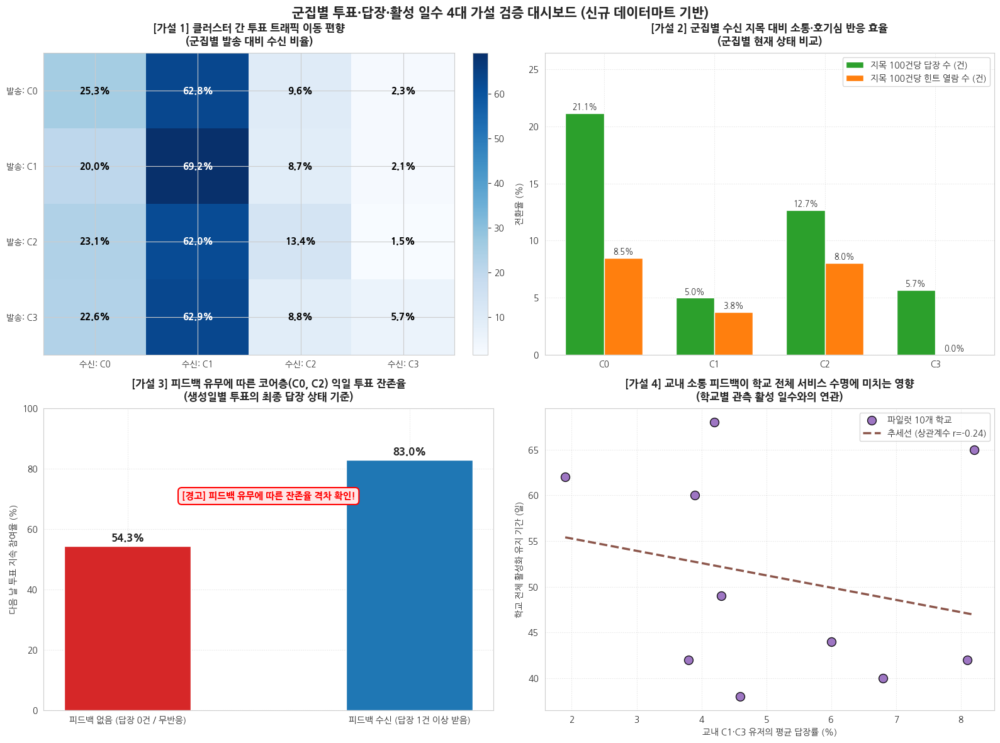

=== [3단계-6] 신규 데이터마트 기반 파이프라인 전체 완료 ===


In [ ]:
# 군집·답장·활동 결과 비교
koreanize_matplotlib.koreanize()
value_fig, value_axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.38, wspace=0.25)
value_ax1 = value_axes[0, 0]
value_im = value_ax1.imshow(value_traffic_matrix_pct.values, cmap='Blues', aspect='auto')
for value_i in range(4):
    for value_j in range(4):
        value_val = value_traffic_matrix_pct.values[value_i, value_j]
        value_color = 'white' if value_val > 30 else 'black'
        value_ax1.text(value_j, value_i, f'{value_val:.1f}%', ha='center', va='center', color=value_color, fontweight='bold', fontsize=11)
value_ax1.set_xticks(range(4))
value_ax1.set_yticks(range(4))
value_ax1.set_xticklabels(['수신: C0', '수신: C1', '수신: C2', '수신: C3'], fontsize=9.5)
value_ax1.set_yticklabels(['발송: C0', '발송: C1', '발송: C2', '발송: C3'], fontsize=9.5)
value_ax1.set_title('[가설 1] 클러스터 간 투표 트래픽 이동 편향\n(군집별 발송 대비 수신 비율)', fontsize=12, fontweight='bold', pad=10)
value_fig.colorbar(value_im, ax=value_ax1, fraction=0.046, pad=0.04)
value_ax2 = value_axes[0, 1]
value_x = np.arange(len(value_step2_summary))
value_w = 0.35
value_r1 = value_ax2.bar(value_x - value_w / 2, value_step2_summary['지목 100건당 답장 수'], value_w, label='지목 100건당 답장 수 (건)', color='#2ca02c')
value_r2 = value_ax2.bar(value_x + value_w / 2, value_step2_summary['지목 100건당 힌트 열람 수'], value_w, label='지목 100건당 힌트 열람 수 (건)', color='#ff7f0e')
value_ax2.set_xticks(value_x)
value_ax2.set_xticklabels(['C0', 'C1', 'C2', 'C3'], fontsize=9.5)
value_ax2.set_ylabel('전환율 (%)', fontsize=10)
value_ax2.set_title('[가설 2] 군집별 수신 지목 대비 소통·호기심 반응 효율\n(군집별 현재 상태 비교)', fontsize=12, fontweight='bold', pad=10)
value_ax2.set_ylim(0, max(value_step2_summary['지목 100건당 답장 수'].max(), value_step2_summary['지목 100건당 힌트 열람 수'].max()) * 1.25)
value_ax2.legend()
value_ax2.grid(True, linestyle=':', alpha=0.6)
for value_rect in list(value_r1) + list(value_r2):
    value_h = value_rect.get_height()
    value_ax2.annotate(f'{value_h:.1f}%', (value_rect.get_x() + value_rect.get_width() / 2, value_h), ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')
value_ax3 = value_axes[1, 0]
value_bars = value_ax3.bar(value_h3_table['피드백 수신 상태'], value_h3_table['다음 날 투표 지속 참여율(%)'], color=['#d62728', '#1f77b4'], width=0.45)
value_ax3.set_ylabel('다음 날 투표 지속 참여율 (%)', fontsize=10)
value_ax3.set_ylim(0, 100)
value_ax3.set_title('[가설 3] 최종 답장 상태별 C0·C2 다음 날 투표 참여율\n(생성일별 투표의 최종 답장 상태 기준)', fontsize=12, fontweight='bold', pad=10)
value_ax3.grid(True, linestyle=':', alpha=0.6)
for value_bar in value_bars:
    value_h = value_bar.get_height()
    value_ax3.annotate(f'{value_h:.1f}%', (value_bar.get_x() + value_bar.get_width() / 2, value_h), ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 3), textcoords='offset points')
value_ax3.annotate(f'[경고] 피드백 유무에 따른 잔존율 격차 확인!', xy=(0.5, 60), xytext=(0.5, 70), ha='center', fontsize=10.5, color='red', fontweight='bold', bbox=dict(boxstyle='round,pad=0.4', fc='#ffe6e6', ec='red', lw=1.5))
value_ax4 = value_axes[1, 1]
value_ax4.scatter(value_sch_df['교내 C1,C3 답장률(%)'], value_sch_df['학교 활성 일수(일)'], color='#9467bd', s=100, alpha=0.9, edgecolors='black', label='파일럿 10개 학교')
value_m, value_b = np.polyfit(value_sch_df['교내 C1,C3 답장률(%)'], value_sch_df['학교 활성 일수(일)'], 1)
value_x_line = np.linspace(value_sch_df['교내 C1,C3 답장률(%)'].min(), value_sch_df['교내 C1,C3 답장률(%)'].max(), 100)
value_ax4.plot(value_x_line, value_m * value_x_line + value_b, color='#8c564b', lw=2.5, linestyle='--', label=f'추세선 (상관계수 r={value_r_corr:.2f})')
value_ax4.set_xlabel('교내 C1·C3 유저의 평균 답장률 (%)', fontsize=10)
value_ax4.set_ylabel('학교 전체 활성화 유지 기간 (일)', fontsize=10)
value_ax4.set_title('[가설 4] 학교별 C1·C3 답장률과 관측 활성 일수의 관계', fontsize=12, fontweight='bold', pad=10)
value_ax4.grid(True, linestyle=':', alpha=0.6)
value_ax4.legend()
plt.suptitle('군집별 투표·답장·활성 일수 4대 가설 검증 대시보드', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()
plt.close()
print('=== 군집·답장·활동 비교 완료 ===')
value_drop('value_flow_df', 'value_df_core_users', 'value_df_user_cluster')


- 사용자·날짜별 최종 답장 상태와 다음 날 투표는 연관됐지만, 10개 학교의 답장률과 활성 일수 사이에서는 유의한 상관을 확인하지 못했다.


### 3-5-7. 최종 미답장 투표일 이후의 참여

- C0·C2가 그날 보낸 지목 중 최종 답장 완료 건이 없는 사용자·날짜를 기준으로 D+1·2·3·5의 투표 여부를 비교했다.
- 발신자·수신자 모두 군집에 속한 투표만 사용한 앞의 비교와 달리, 여기서는 해당 발신자의 전체 투표 기록을 사용했다.
- 당시 답장을 기다리거나 무반응을 경험했다는 기록은 아니다.


In [ ]:
# 미답장 사용자·날짜 표본
koreanize_matplotlib.koreanize()
value_gmm_df = value_df_final.copy()
value_c0_users = set(value_gmm_df[value_gmm_df['cluster'] == 0]['user_id'])
value_c1_users = set(value_gmm_df[value_gmm_df['cluster'] == 1]['user_id'])
value_c2_users = set(value_gmm_df[value_gmm_df['cluster'] == 2]['user_id'])
value_c3_users = set(value_gmm_df[value_gmm_df['cluster'] == 3]['user_id'])
print(f'  * Cluster 0: {len(value_c0_users):,}명')
print(f'  * Cluster 1: {len(value_c1_users):,}명')
print(f'  * Cluster 2: {len(value_c2_users):,}명')
print(f'  * Cluster 3: {len(value_c3_users):,}명')
value_vr = value_read_clean('mart_vote_record_v2')
value_vr['date'] = pd.to_datetime(value_vr['vote_record_created_at']).dt.date
print(f'  * 총 투표 로그 레코드 수: {len(value_vr):,}건')
print('사용자·날짜별 투표와 최종 답장 상태 집계')
value_daily_stat = value_vr.groupby(['voter_user_id', 'date']).agg(votes_count=('user_question_record_id', 'count'), got_reply=('ping_answer_status_current', lambda value_x: (value_x == 'A').sum())).reset_index().rename(columns={'voter_user_id': 'user_id'})
value_all_active_pairs = set(zip(value_daily_stat['user_id'], value_daily_stat['date']))

def value_extract_cohort_survival(value_user_set):
    value_sub = value_daily_stat[value_daily_stat['user_id'].isin(value_user_set)].copy()
    value_no_reply = value_sub[value_sub['got_reply'] == 0].copy()
    value_reply = value_sub[value_sub['got_reply'] > 0].copy()
    value_days_to_track = [1, 2, 3, 4, 5, 7]
    for value_d in value_days_to_track:
        value_no_reply[f'active_d{value_d}'] = pd.MultiIndex.from_arrays([value_no_reply['user_id'], value_no_reply['date'] + pd.Timedelta(days=value_d)]).isin(value_all_active_pairs)
        value_reply[f'active_d{value_d}'] = pd.MultiIndex.from_arrays([value_reply['user_id'], value_reply['date'] + pd.Timedelta(days=value_d)]).isin(value_all_active_pairs)
    return (value_no_reply, value_reply)
value_c0_no_reply, value_c0_reply = value_extract_cohort_survival(value_c0_users)
value_c2_no_reply, value_c2_reply = value_extract_cohort_survival(value_c2_users)
print(f'  * 최종 답장 완료 지목이 없는 사용자·날짜 수: Cluster 0 = {len(value_c0_no_reply):,}건, Cluster 2 = {len(value_c2_no_reply):,}건')
value_drop('value_vr', 'value_daily_stat', 'value_all_active_pairs')


  * Cluster 0: 1,518명
  * Cluster 1: 2,630명
  * Cluster 2: 410명
  * Cluster 3: 291명
  * 총 투표 로그 레코드 수: 1,217,558건
- 3. 유저-일자별 투표 활동 및 피드백 수신 집계 중...
  * 무반응 노출 코호트 케이스 수: Cluster 0 = 8,942건, Cluster 2 = 2,159건


- 최종 미답장 조건에 해당하는 사용자·날짜는 C0 8,942건, C2 2,159건이다. 동일 사용자가 여러 날짜에 포함될 수 있다.


In [ ]:
# 미답장 이후 날짜별 투표 관측
koreanize_matplotlib.koreanize()
value_days_list = [1, 2, 3, 5]
value_days_labels = ['D+0 (기준 투표일)', 'D+1 (익일)', 'D+2', 'D+3', 'D+5']
value_c0_rates = [100.0] + [value_c0_no_reply[f'active_d{value_d}'].mean() * 100 for value_d in value_days_list]
value_c2_rates = [100.0] + [value_c2_no_reply[f'active_d{value_d}'].mean() * 100 for value_d in value_days_list]
value_c0_rep_rates = [100.0] + [value_c0_reply[f'active_d{value_d}'].mean() * 100 for value_d in value_days_list]
value_c2_rep_rates = [100.0] + [value_c2_reply[f'active_d{value_d}'].mean() * 100 for value_d in value_days_list]
value_survival_df = pd.DataFrame({'경과 시점': value_days_labels, 'Cluster 0': [f'{value_v:.1f}%' for value_v in value_c0_rates], 'Cluster 2': [f'{value_v:.1f}%' for value_v in value_c2_rates], '격차 및 패턴 분석': ['기준일 (최종 답장 완료 지목 0건)', f'D+1 투표 관측률 C0 {value_c0_rates[1]:.1f}% vs C2 {value_c2_rates[1]:.1f}%', f'C0 투표 관측률 {value_c0_rates[2]:.1f}%', f'C0 투표 관측률 {value_c0_rates[3]:.1f}%', f'D+5 투표 관측률 C0 {value_c0_rates[4]:.1f}% vs C2 {value_c2_rates[4]:.1f}%']})
print('\n' + '=' * 80)
print('[표 1] 최종 미답장 투표일 이후 날짜별 투표 관측률')
print('=' * 80)
print(value_survival_df.to_string(index=False))



[표 1] 최종 미답장 투표일 이후 경과일별 투표 잔존율 (데이터마트 기반)
       경과 시점 Cluster 0 Cluster 2                         격차 및 패턴 분석
D+0 (기준 투표일)    100.0%    100.0%             기준점 (투표 발송 후 답장 0건 수신)
    D+1 (익일)     53.2%     50.8% 무반응 시 D+1 잔존율 C0 53.2% vs C2 50.8%
         D+2     48.6%     44.8%                   C0 잔존율 48.6%로 급감
         D+3     44.7%     38.8%                 C0 잔존율 44.7% 지속 하락
         D+5     36.6%     31.4%    D+5 장기 잔존율 C0 36.6% vs C2 31.4%


- D+1과 D+5의 투표 관측률은 C0 53.2%·36.6%, C2 50.8%·31.4%다.
- 각 날짜의 투표 여부를 따로 집계한 값이다. 동일 사용자의 반복 기록과 자료 종료의 영향을 보정하지 않아 연속 생존율이나 영구 이탈률로 해석하지 않는다.


### 3-5-8. 다음 날 투표 미참여 비교

- C0·C2 사용자·날짜의 다음 날 투표 미참여 비율을 독립 2표본 Z 검정·카이제곱 검정·오즈비로 비교했다.
- 동일 사용자의 반복 기록은 보정하지 않았다. 앱 전체 이탈이나 결제의 효과를 검증한 결과는 아니다.


In [ ]:
# 독립 2표본 비율 검정·카이제곱·오즈비
koreanize_matplotlib.koreanize()
value_n_c0 = len(value_c0_no_reply)
value_n_c2 = len(value_c2_no_reply)
value_churn_c0 = (~value_c0_no_reply['active_d1']).sum()
value_churn_c2 = (~value_c2_no_reply['active_d1']).sum()
value_z_stat, value_p_val_z = proportions_ztest([value_churn_c0, value_churn_c2], [value_n_c0, value_n_c2])
value_contingency_table = pd.DataFrame([[value_churn_c0, value_n_c0 - value_churn_c0], [value_churn_c2, value_n_c2 - value_churn_c2]], index=['Cluster 0', 'Cluster 2'], columns=['D+1 투표 미참여', 'D+1 재투표'])
value_chi2_val, value_p_val_chi2, value_dof, value__ = stats.chi2_contingency(value_contingency_table)
value_odds_ratio_churn = value_churn_c0 / (value_n_c0 - value_churn_c0) / (value_churn_c2 / (value_n_c2 - value_churn_c2))
print('\n' + '=' * 80)
print('[최종 미답장 투표일 이후 D+1 투표 미참여 비교]')
print('=' * 80)
print(f'- Cluster 0 코호트: N = {value_n_c0:,}건 (D+1 투표 미참여: {value_churn_c0:,}건, {value_churn_c0 / value_n_c0 * 100:.1f}%)')
print(f'- Cluster 2 코호트: N = {value_n_c2:,}건 (D+1 투표 미참여: {value_churn_c2:,}건, {value_churn_c2 / value_n_c2 * 100:.1f}%)')
print(f'- 2-표본 Z 통계량: {value_z_stat:.4f} (p-value: {value_p_val_z:.4e})')
print(f'- 카이제곱 통계량 (Chi2): {value_chi2_val:,.4f} (자유도: {value_dof}, p-value: {value_p_val_chi2:.4e})')
print(f'- 미참여 오즈비 (Odds Ratio): {value_odds_ratio_churn:.4f}배')
print('=' * 80)



[정식 통계 검정 결과: 무반응 노출 시 D+1 투표 미참여 격차 (데이터마트 기반)]
- Cluster 0 코호트: N = 8,942건 (D+1 투표 미참여: 4,183건, 46.8%)
- Cluster 2 코호트: N = 2,159건 (D+1 투표 미참여: 1,062건, 49.2%)
- 2-표본 Z 통계량: -2.0133 (p-value: 4.4085e-02)
- 카이제곱 통계량 (Chi2): 3.9572 (자유도: 1, p-value: 4.6672e-02)
- 미참여 오즈비 (Odds Ratio): 0.9079배


- 다음 날 투표 미참여 비율은 C0 46.8%, C2 49.2%로 C2가 약 2.41%p 높다.
- 독립 2표본 Z 검정의 p값은 0.0441이다. 동일 사용자의 반복 기록을 보정하지 않은 탐색적 비교이며, 결제의 인과효과나 영구 이탈 차이를 뜻하지 않는다.


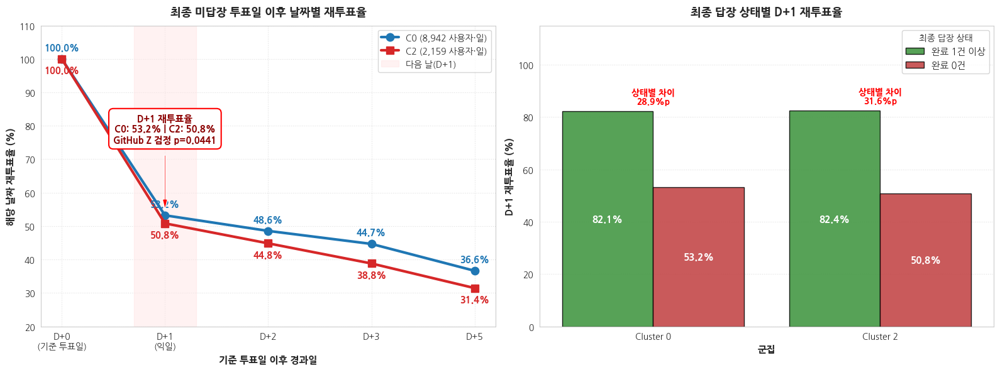

군집별 날짜별 투표 참여 비교 완료


In [ ]:
# 유형별 날짜별 투표 참여와 독립비율 검정
koreanize_matplotlib.koreanize()
value_fig, (value_ax1, value_ax2) = plt.subplots(1, 2, figsize=(16, 6))
value_x_ticks = [0, 1, 2, 3, 4]
value_x_labels = ['D+0\n(기준 투표일)', 'D+1\n(익일)', 'D+2', 'D+3', 'D+5']
value_ax1.plot(value_x_ticks, value_c0_rates, marker='o', markersize=9, lw=3,
               color='#1f77b4', label=f'C0 ({value_n_c0:,} 사용자·일)')
value_ax1.plot(value_x_ticks, value_c2_rates, marker='s', markersize=9, lw=3,
               color='#d62728', label=f'C2 ({value_n_c2:,} 사용자·일)')
for value_i, (value_r0, value_r2) in enumerate(zip(value_c0_rates, value_c2_rates)):
    value_ax1.annotate(f'{value_r0:.1f}%', (value_x_ticks[value_i], value_r0),
                      textcoords='offset points', xytext=(0, 10), ha='center',
                      fontsize=10.5, fontweight='bold', color='#1f77b4')
    value_ax1.annotate(f'{value_r2:.1f}%', (value_x_ticks[value_i], value_r2),
                      textcoords='offset points', xytext=(0, -16), ha='center',
                      fontsize=10.5, fontweight='bold', color='#d62728')
value_ax1.axvspan(0.7, 1.3, color='#ffe6e6', alpha=0.5, label='다음 날(D+1)')
value_ax1.annotate(
    f'D+1 재투표율\nC0: {value_c0_rates[1]:.1f}% | C2: {value_c2_rates[1]:.1f}%\n'
    f'독립 2표본 Z 검정 p={value_p_val_z:.3g}',
    xy=(1, value_c0_rates[1]), xytext=(1, 75), ha='center', fontsize=10.5,
    color='darkred', fontweight='bold',
    arrowprops=dict(facecolor='red', shrink=0.08, width=1.5, headwidth=6),
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='red', lw=1.5),
)
value_ax1.set_title('최종 미답장 투표일 이후 날짜별 재투표율', fontsize=13, fontweight='bold', pad=12)
value_ax1.set_xlabel('기준 투표일 이후 경과일', fontsize=11, fontweight='bold')
value_ax1.set_ylabel('해당 날짜 재투표율 (%)', fontsize=11, fontweight='bold')
value_ax1.set_xticks(value_x_ticks)
value_ax1.set_xticklabels(value_x_labels, fontsize=10)
value_ax1.set_ylim(20, 110)
value_ax1.grid(True, linestyle=':', alpha=0.6)
value_ax1.legend(fontsize=10, loc='upper right')
value_feedback_comp_df = pd.DataFrame({
    '군집': ['Cluster 0', 'Cluster 0', 'Cluster 2', 'Cluster 2'],
    '최종 답장 상태': ['완료 1건 이상', '완료 0건', '완료 1건 이상', '완료 0건'],
    'D+1 재투표율 (%)': [
        value_c0_rep_rates[1], value_c0_rates[1], value_c2_rep_rates[1], value_c2_rates[1]
    ],
})
sns.barplot(data=value_feedback_comp_df, x='군집', y='D+1 재투표율 (%)',
            hue='최종 답장 상태', palette=['#2ca02c', '#d62728'],
            ax=value_ax2, edgecolor='black', alpha=0.85)
for value_p in value_ax2.patches:
    value_height = value_p.get_height()
    if value_height > 0:
        value_ax2.annotate(f'{value_height:.1f}%',
                          (value_p.get_x() + value_p.get_width() / 2.0, value_height / 2),
                          ha='center', va='center', fontsize=11, color='white', fontweight='bold')
value_drop_c0 = value_c0_rep_rates[1] - value_c0_rates[1]
value_drop_c2 = value_c2_rep_rates[1] - value_c2_rates[1]
value_ax2.set_title('최종 답장 상태별 D+1 재투표율', fontsize=13, fontweight='bold', pad=12)
value_ax2.set_ylabel('D+1 재투표율 (%)', fontsize=11, fontweight='bold')
value_ax2.set_xlabel('군집', fontsize=11, fontweight='bold')
value_ax2.set_ylim(0, 115)
value_ax2.set_yticks(np.arange(0, 101, 20))
value_ax2.grid(True, linestyle=':', alpha=0.6, axis='y')
value_ax2.legend(title='최종 답장 상태', fontsize=10.5, loc='upper right')
value_ax2.text(0, value_c0_rep_rates[1] + 3, f'상태별 차이\n{value_drop_c0:.1f}%p',
               ha='center', color='red', fontweight='bold', fontsize=10)
value_ax2.text(1, value_c2_rep_rates[1] + 3, f'상태별 차이\n{value_drop_c2:.1f}%p',
               ha='center', color='red', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()
print('군집별 날짜별 투표 참여 비교 완료')
value_drop('value_c0_no_reply', 'value_c0_reply', 'value_c2_no_reply', 'value_c2_reply',
           'value_gmm_df')


**Value 요약**

- 지목이 집중되는 집단과 수신 지목 대비 답장 비율이 높은 집단은 달랐다.
- 최종 답장 완료 지목이 있는 사용자·날짜에서 다음 날 투표율이 높았지만, 실제 답장 시각과 참여의 선후관계는 확인하지 못했다.
- 10개 학교의 결과이며, 동일 사용자의 반복 기록·학교와 날짜의 공통 요인·자료 종료의 영향을 보정하지 않았다.


In [ ]:
# Value 요약·임시 변수 정리
value_results = {
    '모집단': value_cohort_audit,
    '지표 집계 대사': value_feature_audit,
    'GMM 적합도': value_eval_df,
    '군집 핵심 지표': value_summary_5,
    '군집 행동 지표': value_summary_act,
    '군집 이동 비율': value_traffic_pct_display,
    '군집 반응 비교': value_step2_summary,
    '답장 상태별 익일 투표': value_h3_table,
    '학교별 활성 일수': value_sch_df,
    '경과일 재투표율': value_survival_df,
    '익일 미참여 비교': value_contingency_table,
    '독립비율 검정': pd.DataFrame([{'검정': 'Z', '통계량': value_z_stat, 'p_value': value_p_val_z}, {'검정': '카이제곱', '통계량': value_chi2_val, 'p_value': value_p_val_chi2}]),
    '답장 상태·군집별 익일 투표': value_feedback_comp_df,
}
value_drop('value_df_c', 'value_eda_reference', 'value_df_core', 'value_mart')
print('3-5. Value 완료 — 사용자별 군집은 value_df_final, 주요 결과표는 value_results에 남겼습니다.')


3-5. Value 완료 — 사용자별 군집은 value_df_final, 주요 결과표는 value_results에 남겼습니다.


## 3-6. Trust

- 질문 피드백의 사유를 선호·품질·잠재 안전으로 구분하고, 수동 라벨과 텍스트 모델로 검토 우선순위를 분석했다.
- 잠재 안전은 피드백 사유에 따른 분류이며, 실제 위해가 확인된 사례 수와 다르다.


### 3-6-1. 수동 라벨과 질문 연결

- 같은 문구에 여러 질문 ID가 있을 수 있어 문구 단위와 ID 단위를 구분했다.


In [ ]:
# Trust·Continuation 공통 연결
T7TC_PROCESSED = Path(globals().get('PREPROCESSED_ROOT', '/content/team7_processed'))
T7TC_CONTENT = Path('/content/team7_analysis/content/outputs')
T7TC_INTERACTION = Path('/content/team7_runtime/interaction')

def t7tc_style():
    sns.set_theme(style='whitegrid')
    koreanize_matplotlib.koreanize()

def t7tc_clean_path(name):
    key = re.sub(r'(_clean)?\.csv(\.gz)?$', '', name)
    if key.endswith('_clean'):
        key = key[:-6]
    found = list(T7TC_PROCESSED.rglob(key + '_clean.csv.gz'))
    found += list(T7TC_PROCESSED.rglob(key + '_clean.csv'))
    if len(found) != 1:
        raise FileNotFoundError(f'2번 전처리 결과를 확인해 주세요: {key} ({found})')
    return found[0]

def t7tc_read_clean(name, usecols=None, **kwargs):
    return pd.read_csv(t7tc_clean_path(name), usecols=usecols,
                       na_values=[r'\N'], low_memory=False, **kwargs)

def t7tc_school_read(name, required):
    path = t7tc_clean_path(name)
    header = pd.read_csv(path, nrows=0).columns.tolist()
    missing = sorted(set(required) - set(header))
    if missing:
        raise ValueError(f'{name} 필수 컬럼 누락: {missing}')
    cols = list(required)
    if 'user_activity_daily' in name:
        optional = ['friend_request_sent_count', 'friend_request_received_count',
                    'db_payment_success_count', 'db_payment_fail_count',
                    'user_initiated_activity_proxy_flag', 'any_record_observed_flag',
                    'context_or_system_only_day_flag']
        cols += [c for c in optional if c in header and c not in cols]
    parts = []
    for chunk in pd.read_csv(path, usecols=cols, chunksize=250000, na_values=[r'\N']):
        for col in chunk:
            if col.endswith(('_count', '_flag')):
                chunk[col] = pd.to_numeric(chunk[col], errors='raise', downcast='integer')
            elif col in ('activity_date', 'current_roster_40th_signup_at', 'user_created_at'):
                chunk[col] = pd.to_datetime(chunk[col], format='mixed', errors='coerce')
        parts.append(chunk)
    result = pd.concat(parts, ignore_index=True)
    del parts
    gc.collect()
    return result

def t7tc_follow_read(name, cols=None):
    # 분석에 필요한 정제 마트 컬럼을 확인한다.
    # Interaction의 시각 매칭 복원 결과로 방문·사용자 식별을 대체하지 않는다.
    frame = t7tc_read_clean(name, usecols=cols)
    if name == 'mart_hackle_user_daily_24d_v2' and 'hackle_ping_open_count' not in frame:
        raise ValueError('정제 마트에 필요한 hackle_ping_open_count가 없습니다. 입력 컬럼을 확인하세요.')
    return frame

def t7tc_release(prefix):
    names = [name for name in list(globals()) if name.startswith(prefix)]
    for name in names:
        globals().pop(name, None)
    plt.close('all')
    gc.collect()
    print('임시 변수 정리:', prefix)

t7tc_style()
print('Trust·Continuation 입력 확인 완료.')

trust_label_data, TRUST_LABEL_PATH = team7_load_trust_labels()
display(trust_label_data['label'].value_counts().rename('문구 수').to_frame())


Trust·Continuation 공통 연결 준비 완료. 분석 결과는 화면에만 표시합니다.
라벨링 로드: trust_question_review_all_labeled_clean.csv | 문구 2,964개 · 질문 ID 3,088개


,문구 수
label,
관계_호감_친밀도,598
성격_사회성,550
취향_일상,491
능력_재능,403
외모_신체_평가,321
연애,285
매력,192
학교_학업,89
음주_폭력,21


- 수동 라벨은 문구 2,964개, 열 가지 유형으로 구성돼 있다. 관계·호감·친밀도 598개와 성격·사회성 550개가 많고, 외모·신체 비하는 14개로 가장 적다.


In [ ]:
# Trust 분류 분석 설정
t7tc_style()
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 160)

def tm_load_mart(tm_name, **tm_kwargs):
    return t7tc_read_clean(tm_name, **tm_kwargs)
print('질문 카테고리·모델 분석: 기존 정제 마트 및 mart 폴더의 수동 라벨 사용')
plt.close('all')
_t7tc_collected = gc.collect()


질문 카테고리·모델 분석: 기존 정제 마트 및 mart 폴더의 수동 라벨 사용


In [ ]:
# 수동 라벨 구조·결측 확인
# 라벨 CSV를 읽고 질문 문구의 앞뒤 공백을 유지한다.
tm_labeled = pd.read_csv(TRUST_LABEL_PATH, dtype=str)
print('labeled shape:', tm_labeled.shape)
print('중복 행:', tm_labeled.duplicated().sum())
print('결측치:\n', tm_labeled.isna().sum())
print()
print('label 분포:')
display(tm_labeled['label'].value_counts())
plt.close('all')
_t7tc_collected = gc.collect()


labeled shape: (2964, 3)
중복 행: 0
결측치:
 question_id    0
question       0
label          0
dtype: int64

label 분포:


,count
label,
관계_호감_친밀도,598
성격_사회성,550
취향_일상,491
능력_재능,403
외모_신체_평가,321
연애,285
매력,192
학교_학업,89
음주_폭력,21


- 수동 라벨 2,964행에 중복 행과 결측치는 없었다. 복수 질문 ID가 포함된 행은 ID별로 펼쳤다.


In [ ]:
# 분류명 정리
tm_labeled['label'] = tm_labeled['label'].replace({'매력': '개성'})
print('[OK] 카테고리명 변경 반영: 매력 -> 개성')
print(tm_labeled['label'].value_counts())
plt.close('all')
_t7tc_collected = gc.collect()


[OK] 카테고리명 변경 반영: 매력 -> 개성
label
관계_호감_친밀도    598
성격_사회성       550
취향_일상        491
능력_재능        403
외모_신체_평가     321
연애           285
개성           192
학교_학업         89
음주_폭력         21
외모_신체_비하      14
Name: count, dtype: int64


- 유형 비교에서는 ‘매력’을 ‘개성’으로 표시했다. 뒤의 수동 라벨 점검에서는 라벨 파일의 분류명 ‘매력’을 사용했다.


In [ ]:
# 질문 ID 펼치기
tm_exploded = tm_labeled.assign(question_id=tm_labeled['question_id'].str.split('\\s*\\|\\s*')).explode('question_id')
tm_exploded['question_id'] = tm_exploded['question_id'].str.strip().astype(int)
print('explode 전:', tm_labeled.shape[0], '행 / explode 후:', tm_exploded.shape[0], '행')
assert tm_exploded['question_id'].is_unique, '동일 question_id가 서로 다른 라벨에 중복 매핑되면 안 됨'
print('[OK] 모든 question_id가 고유 — 라벨 충돌 없음')
tm_cat_map = tm_exploded.set_index('question_id')['label']
plt.close('all')
_t7tc_collected = gc.collect()


explode 전: 2964 행 / explode 후: 3088 행
[OK] 모든 question_id가 고유 — 라벨 충돌 없음


- ID를 펼치면 2,964행이 3,088행이 된다. 모든 질문 ID가 고유해서 같은 ID에 서로 다른 라벨이 붙는 충돌은 없었다.


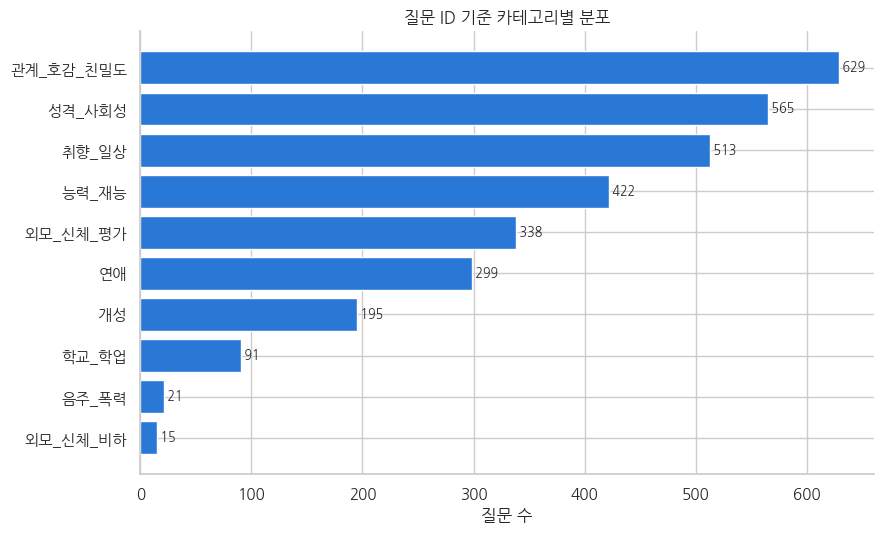

In [ ]:
# 질문 ID 기준 유형 분포
tm_cat_counts = tm_exploded.groupby('label').size().sort_values(ascending=True)
tm_fig, tm_ax = plt.subplots(figsize=(9, 5.5))
tm_ax.barh(tm_cat_counts.index, tm_cat_counts.values, color='#2a78d6')
tm_ax.set_xlabel('질문 수')
tm_ax.set_title('질문 ID 기준 카테고리별 분포')
for tm_i, tm_v in enumerate(tm_cat_counts.values):
    tm_ax.text(tm_v, tm_i, f' {tm_v}', va='center', fontsize=9)
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 질문 ID 기준으로도 관계·호감·친밀도 629개, 성격·사회성 565개가 가장 많다. 외모·신체 비하는 15개다. 유형별 공급량 차이가 커 피드백 건수만 나란히 두면 크기를 오해하기 쉽다.


### 3-6-2. 질문 유형별 피드백 비교

- 전체 학교의 피드백을 질문 ID 수로 나눠 유형별로 비교했다. 질문당 피드백 건수와 피드백 안의 사유 비중은 서로 다른 지표다.
- 질문 배치 자료는 10개 학교에 한정돼 있다. 전체 학교 피드백을 이 배치 수로 나누지 않고, 학교 범위를 맞춘 비교는 뒤에서 따로 확인했다.
- 표의 ‘신고건수’에는 선호·품질·긍정 피드백도 포함된다. 안전 문제만의 순위는 아니다.


In [ ]:
# 안전 마트 채널·사유 확인
tm_safety = tm_load_mart('mart_safety_event_v2_clean')
print('safety shape:', tm_safety.shape)
print()
print('record_type 분포:')
display(tm_safety['record_type'].value_counts())
tm_reports = tm_safety[tm_safety['record_type'] == 'QUESTION_FEEDBACK_OR_REPORT'].copy()
tm_reports['question_id'] = tm_reports['question_id'].astype(int)
tm_reports['label'] = tm_reports['question_id'].map(tm_cat_map)
tm_n_known = tm_reports['label'].notna().sum()
tm_n_unknown = tm_reports['label'].isna().sum()
print(f'\n신고 이벤트 총 {len(tm_reports):,}건 중 우리 라벨 데이터에 있는 질문: {tm_n_known:,}건, 없는 질문: {tm_n_unknown:,}건')
print('(라벨이 연결되지 않은 질문은 유형 비교에서 제외한다. 미연결 원인은 별도 확인이 필요하다.)')
tm_reports_known = tm_reports[tm_reports['label'].notna()].copy()
plt.close('all')
_t7tc_collected = gc.collect()


safety shape: (71283, 41)

record_type 분포:


,count
record_type,
QUESTION_FEEDBACK_OR_REPORT,51424
USER_BLOCK,19482
TIMELINE_REPORT,208
PING_REPORT_COUNT_SNAPSHOT,169



신고 이벤트 총 51,424건 중 우리 라벨 데이터에 있는 질문: 50,926건, 없는 질문: 498건
(라벨이 연결되지 않은 질문은 유형 비교에서 제외한다. 미연결 원인은 별도 확인이 필요하다.)


- 안전 마트 71,283행 중 질문 피드백은 51,424행이다. 나머지는 사용자 차단, 타임라인 신고, Ping 신고 상태다.

- 질문 피드백 가운데 50,926행에 라벨이 붙었고, 미연결 498행은 이번 유형 비교에서 빠졌다.


In [ ]:
# 질문조각 기준 분모 연결
tm_exposure = tm_load_mart('mart_question_exposure_clean', usecols=['question_id', 'piece_exists_flag', 'report_count'])
print('exposure shape:', tm_exposure.shape)
print('report_count가 0인 비율:', (tm_exposure['report_count'].fillna(0) == 0).mean().round(3))
tm_exposure_count = tm_exposure[tm_exposure['piece_exists_flag'] == 1].groupby('question_id').size()
print('\n노출 근사치가 없는 라벨 질문 수:', tm_exposure_count.reindex(tm_cat_map.index).isna().sum(), '/', len(tm_cat_map))
plt.close('all')
_t7tc_collected = gc.collect()


exposure shape: (1583840, 3)
report_count가 0인 비율: 1.0

노출 근사치가 없는 라벨 질문 수: 0 / 3088


- 라벨이 있는 질문 ID 3,088개 모두 질문조각 수와 연결됐다. 조각 자료의 `report_count`는 전부 0이라 피드백 건수는 별도 피드백 자료에서 가져왔다.
- 질문조각은 질문세트에 배치된 기록이다. 사용자가 화면을 실제로 읽은 횟수는 아니다.


In [ ]:
# 질문 유형별 피드백 집계
tm_summary_rows = []
for tm_cat, tm_sub in tm_exploded.groupby('label'):
    tm_qids = tm_sub['question_id'].astype(int)
    tm_n_q = len(tm_qids)
    tm_n_reports = tm_reports_known[tm_reports_known['label'] == tm_cat].shape[0]
    tm_n_exposure = tm_exposure_count.reindex(tm_qids).sum()
    tm_summary_rows.append({'카테고리': tm_cat, '질문수': tm_n_q, '신고건수': tm_n_reports, '질문당_신고건수': round(tm_n_reports / tm_n_q, 2), '노출횟수(10개교 owner 기준)': int(tm_n_exposure)})
tm_report_summary = pd.DataFrame(tm_summary_rows).sort_values('질문당_신고건수', ascending=False).reset_index(drop=True)
display(tm_report_summary)
plt.close("all")
_t7tc_collected = gc.collect()


,카테고리,질문수,신고건수,질문당_신고건수,노출횟수(10개교 owner 기준)
0,외모_신체_비하,15,1348,89.8700,6059
1,음주_폭력,21,662,31.5200,16091
2,외모_신체_평가,338,7989,23.6400,148725
3,개성,195,3787,19.4200,99872
4,연애,299,5280,17.6600,103700
5,능력_재능,422,6982,16.5500,187515
6,성격_사회성,565,9050,16.0200,250319
7,취향_일상,513,6881,13.4100,133805
8,학교_학업,91,1201,13.2000,38822
9,관계_호감_친밀도,629,7746,12.3100,242176


- 전체 피드백 건수는 성격·사회성이 9,050건으로 가장 많다. 질문 한 개당으로 나누면 외모·신체 비하가 89.87건, 음주·폭력이 31.52건이다.
- 외모·신체 비하는 질문 ID 15개에 피드백 1,348건이 모였다. 질문 수가 적은 유형이라 문구별 집중도도 함께 볼 필요가 있다.


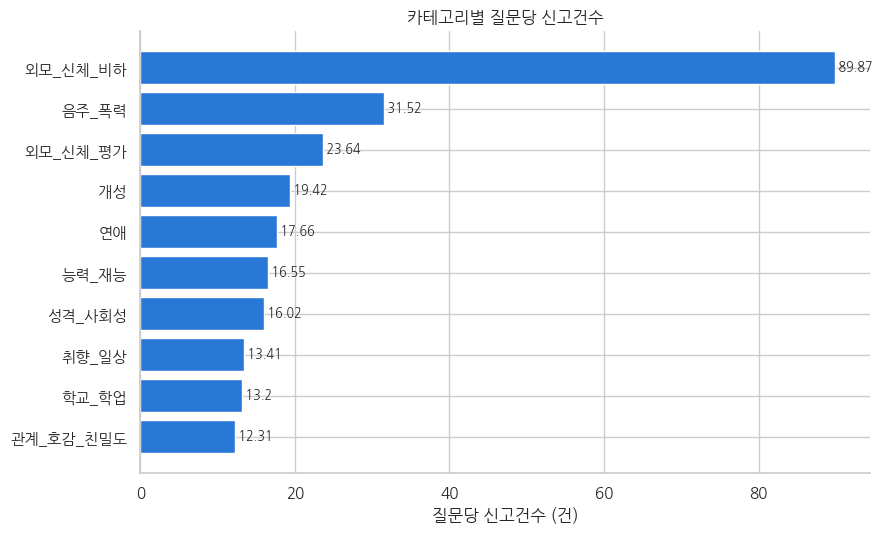

In [ ]:
# 질문당 피드백 비교 차트
tm_fig, tm_ax = plt.subplots(figsize=(9, 5.5))
tm_order = tm_report_summary.sort_values('질문당_신고건수', ascending=True)
tm_ax.barh(tm_order['카테고리'], tm_order['질문당_신고건수'], color='#2a78d6')
tm_ax.set_xlabel('질문당 신고건수 (건)')
tm_ax.set_title('카테고리별 질문당 신고건수')
for tm_i, tm_v in enumerate(tm_order['질문당_신고건수']):
    tm_ax.text(tm_v, tm_i, f' {tm_v}', va='center', fontsize=9)
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close("all")
_t7tc_collected = gc.collect()


- 외모·신체 비하 질문은 한 개당 평균 약 90건의 피드백을 받았다. 이 값은 비율이 아니라 건수다.
- 관계·호감·친밀도는 629문항, 외모·신체 비하는 15문항이다. 유형별 질문 수가 크게 다르다는 점을 함께 봐야 한다.


In [ ]:
# 질문 유형·피드백 사유 교차표
print('=== feedback_domain_rule_v1 x 카테고리 (신고 건수) ===')
tm_domain_ct = pd.crosstab(tm_reports_known['label'], tm_reports_known['feedback_domain_rule_v1'])
display(tm_domain_ct)
print('\n=== safety_interpretation_rule_v1 x 카테고리 (행 기준 비율 %) ===')
tm_interp_ct = pd.crosstab(tm_reports_known['label'], tm_reports_known['safety_interpretation_rule_v1'], normalize='index') * 100
display(tm_interp_ct.round(1).sort_values('POTENTIAL_SAFETY', ascending=False))
plt.close('all')
_t7tc_collected = gc.collect()


=== feedback_domain_rule_v1 x 카테고리 (신고 건수) ===


feedback_domain_rule_v1,CONTENT_QUALITY,CONTENT_REPETITION,CONTENT_SAFETY,OTHER,PERSONAL_PREFERENCE,POSITIVE_FEEDBACK,RELATIONSHIP_FREQUENCY
label,,,,,,,
개성,62,201,530,53,2593,190,158
관계_호감_친밀도,62,475,520,100,5777,448,364
능력_재능,93,514,607,69,5293,210,196
성격_사회성,90,688,701,71,6883,324,293
연애,30,237,830,39,3778,168,198
외모_신체_비하,6,49,416,2,856,6,13
외모_신체_평가,102,410,1238,86,5636,306,211
음주_폭력,7,31,68,6,509,23,18
취향_일상,75,441,666,46,5360,101,192



=== safety_interpretation_rule_v1 x 카테고리 (행 기준 비율 %) ===


safety_interpretation_rule_v1,OTHER,POSITIVE_FEEDBACK,POTENTIAL_SAFETY,PRODUCT_OR_RELATIONSHIP_FEEDBACK
label,,,,
외모_신체_비하,0.1000,0.4000,30.9000,68.5000
연애,0.7000,3.2000,15.7000,80.4000
외모_신체_평가,1.1000,3.8000,15.5000,79.6000
개성,1.4000,5.0000,14.0000,79.6000
음주_폭력,0.9000,3.5000,10.3000,85.3000
취향_일상,0.7000,1.5000,9.7000,88.2000
능력_재능,1.0000,3.0000,8.7000,87.3000
성격_사회성,0.8000,3.6000,7.7000,87.9000
학교_학업,0.3000,3.0000,6.9000,89.8000


- 모든 질문 유형에서 개인 선호 사유가 가장 큰 부분을 차지한다. 외모·신체 비하도 개인 선호 856건과 잠재 안전 416건이 함께 있다. 같은 유형 안에서도 불편한 이유가 하나로 모이지는 않았다.


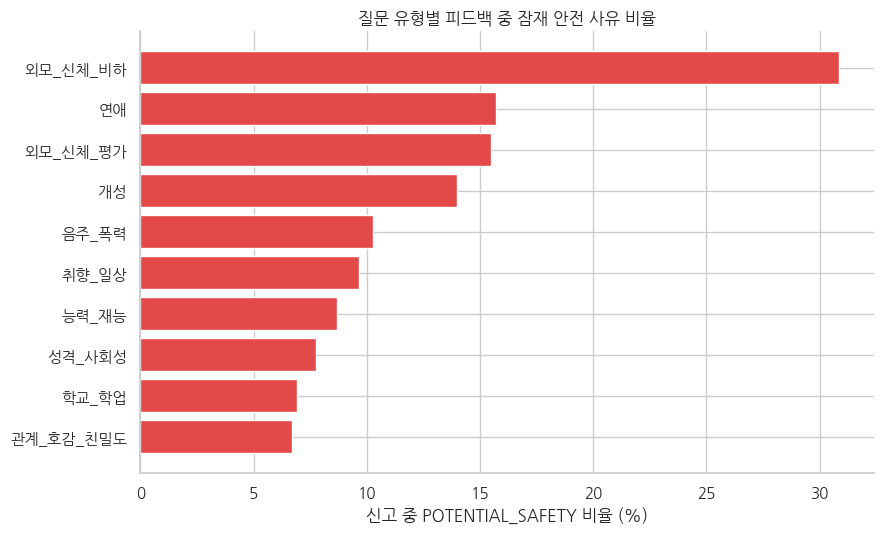

In [ ]:
# 유형별 잠재 안전 사유 구성
tm_potential_safety_share = tm_interp_ct['POTENTIAL_SAFETY'].sort_values(ascending=True)
tm_fig, tm_ax = plt.subplots(figsize=(9, 5.5))
tm_ax.barh(tm_potential_safety_share.index, tm_potential_safety_share.values, color='#e34948')
tm_ax.set_xlabel('신고 중 POTENTIAL_SAFETY 비율 (%)')
tm_ax.set_title('질문 유형별 피드백 중 잠재 안전 사유 비율')
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 피드백 안의 잠재 안전 비중은 외모·신체 비하 30.9%, 연애 15.7%, 외모·신체 평가 15.5% 순이다. 관계·호감·친밀도는 6.7%로 낮았다.


### 3-6-3. 선호·품질·안전 사유 구분

- 피드백을 개인화·제품 품질·안전 검토 영역으로 구분하고, 반응이 집중된 질문 문구를 확인했다.


In [ ]:
# 세 가지 피드백 영역 분류
tm_SAFETY_DOMAINS = ['CONTENT_SAFETY', 'HARASSMENT', 'MISINFORMATION', 'SPAM', 'ACCOUNT_INTEGRITY']
tm_PRODUCT_QUALITY_DOMAINS = ['CONTENT_QUALITY', 'CONTENT_REPETITION']
tm_PERSONALIZATION_DOMAINS = ['PERSONAL_PREFERENCE', 'RELATIONSHIP_MISMATCH', 'RELATIONSHIP_FREQUENCY', 'RELATIONSHIP_RELEVANCE']

def tm_classify_domain(tm_v):
    if tm_v in tm_SAFETY_DOMAINS:
        return 'Safety'
    if tm_v in tm_PRODUCT_QUALITY_DOMAINS:
        return 'Product Quality'
    if tm_v in tm_PERSONALIZATION_DOMAINS:
        return 'Personalization'
    return '기타(긍정/기타)'
tm_reports_known['trust_category'] = tm_reports_known['feedback_domain_rule_v1'].map(tm_classify_domain)
display(tm_reports_known['trust_category'].value_counts())
plt.close('all')
_t7tc_collected = gc.collect()


,count
trust_category,
Personalization,39287
Safety,5659
Product Quality,3692
기타(긍정/기타),2288


- 개인화 39,287건, 잠재 안전 5,659건, 제품 품질 3,692건, 긍정·기타 2,288건이다.
- 선호 불일치와 안전 우려를 구분해야 피드백 사유에 맞는 대응을 설계할 수 있다.


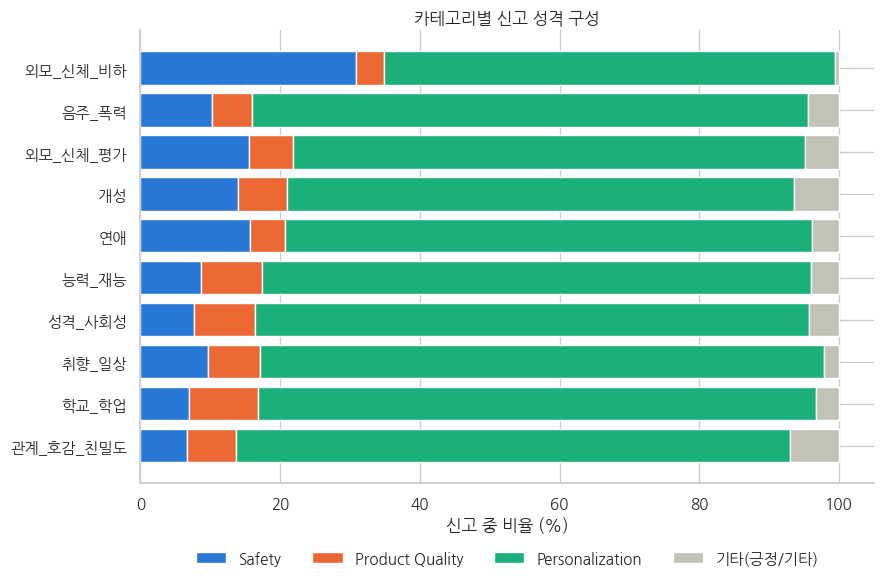

In [ ]:
# 유형별 선호·품질·안전 비중
tm_GROUP_COLORS = {'Safety': '#2a78d6', 'Product Quality': '#eb6834', 'Personalization': '#1baf7a', '기타(긍정/기타)': '#c3c2b7'}
tm_GROUP_ORDER = ['Safety', 'Product Quality', 'Personalization', '기타(긍정/기타)']
tm_cat_group_pct = pd.crosstab(tm_reports_known['label'], tm_reports_known['trust_category'], normalize='index')[tm_GROUP_ORDER] * 100
tm_cat_group_pct = tm_cat_group_pct.loc[tm_report_summary.sort_values('질문당_신고건수', ascending=True)['카테고리']]
tm_fig, tm_ax = plt.subplots(figsize=(9, 6))
tm_left = pd.Series(0, index=tm_cat_group_pct.index, dtype=float)
for tm_grp in tm_GROUP_ORDER:
    tm_ax.barh(tm_cat_group_pct.index, tm_cat_group_pct[tm_grp], left=tm_left, color=tm_GROUP_COLORS[tm_grp], label=tm_grp)
    tm_left += tm_cat_group_pct[tm_grp]
tm_ax.set_xlabel('신고 중 비율 (%)')
tm_ax.set_title('카테고리별 신고 성격 구성')
tm_ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close("all")
_t7tc_collected = gc.collect()


- 외모·신체 비하는 다른 유형보다 안전 사유가 차지하는 비중이 크다. 관계·호감·친밀도는 개인화 쪽 비중이 크다. 유형마다 같은 신고 건수라도 구성은 다르다.


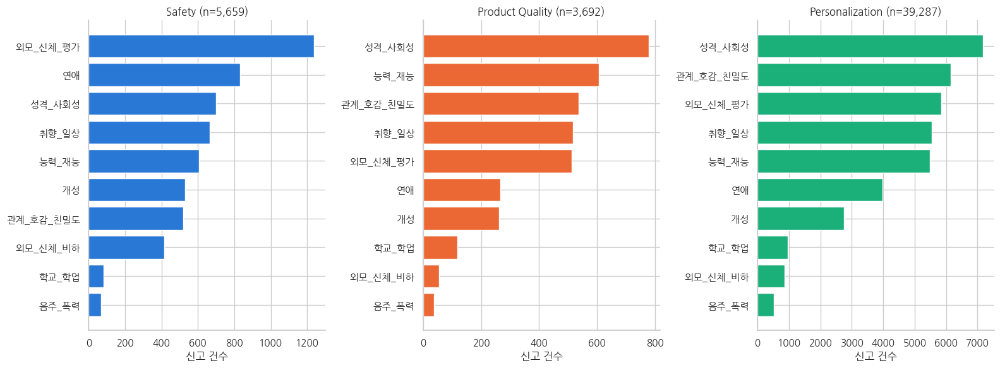

In [ ]:
# 피드백 영역별 비교 차트
tm_core_groups = ['Safety', 'Product Quality', 'Personalization']
tm_fig, tm_axes = plt.subplots(1, 3, figsize=(16, 6), sharex=False)
for tm_ax, tm_grp in zip(tm_axes, tm_core_groups):
    tm_sub = tm_reports_known[tm_reports_known['trust_category'] == tm_grp]
    tm_counts = tm_sub['label'].value_counts().sort_values(ascending=True)
    tm_ax.barh(tm_counts.index, tm_counts.values, color=tm_GROUP_COLORS[tm_grp])
    tm_ax.set_title(f'{tm_grp} (n={len(tm_sub):,})')
    tm_ax.set_xlabel('신고 건수')
    for tm_spine in ['top', 'right']:
        tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 잠재 안전 피드백은 외모·신체 평가 1,238건이 가장 많다. 비중이 가장 높았던 외모·신체 비하는 416건이다.

- 검토량을 잡을 때는 건수, 유형 안의 반응을 볼 때는 비중이 각각 필요하다.


In [ ]:
# 싫어요·안전 사유 비교
tm_reports_known['is_geunyang_sireo'] = tm_reports_known['reason_raw'] == '그냥 싫어'
tm_EXPLICIT_SAFETY_REASONS = ['불쾌한 질문 내용', '불쾌한 내용이 포함되어 있음', '선정적이거나 자극적인 질문']
tm_reports_known['is_explicit_safety'] = tm_reports_known['reason_raw'].isin(tm_EXPLICIT_SAFETY_REASONS)
tm_reason_check = tm_reports_known.groupby('label').agg(총신고=('reason_raw', 'size'), 그냥싫어_건=('is_geunyang_sireo', 'sum'), 명시적안전사유_건=('is_explicit_safety', 'sum')).reset_index()
tm_reason_check['그냥싫어_비율'] = (tm_reason_check['그냥싫어_건'] / tm_reason_check['총신고'] * 100).round(1)
tm_reason_check['명시적안전사유_비율'] = (tm_reason_check['명시적안전사유_건'] / tm_reason_check['총신고'] * 100).round(1)
tm_reason_check = tm_reason_check.sort_values('명시적안전사유_비율', ascending=False)
display(tm_reason_check)
print(f"전체 평균 '그냥 싫어' 비율: {tm_reports_known['is_geunyang_sireo'].mean() * 100:.1f}%")
print(f"전체 평균 명시적 안전 사유 비율: {tm_reports_known['is_explicit_safety'].mean() * 100:.1f}%")
plt.close('all')
_t7tc_collected = gc.collect()


,label,총신고,그냥싫어_건,명시적안전사유_건,그냥싫어_비율,명시적안전사유_비율
5,외모_신체_비하,1348,690,416,51.2000,30.9000
4,연애,5280,2992,830,56.7000,15.7000
6,외모_신체_평가,7989,4387,1238,54.9000,15.5000
0,개성,3787,1945,530,51.4000,14.0000
7,음주_폭력,662,389,68,58.8000,10.3000
8,취향_일상,6881,3833,666,55.7000,9.7000
2,능력_재능,6982,3851,607,55.2000,8.7000
3,성격_사회성,9050,4802,701,53.1000,7.7000
9,학교_학업,1201,618,83,51.5000,6.9000
1,관계_호감_친밀도,7746,4660,520,60.2000,6.7000


전체 평균 '그냥 싫어' 비율: 55.3%
전체 평균 명시적 안전 사유 비율: 11.1%


- ‘그냥 싫어’는 전체 피드백의 55.3%, 명시적 안전 사유는 11.1%다. 관계·호감·친밀도는 ‘그냥 싫어’ 60.2%로 높지만 안전 사유는 6.7%다. 싫다는 반응의 크기만으로 안전 우려를 대신하기 어렵다.


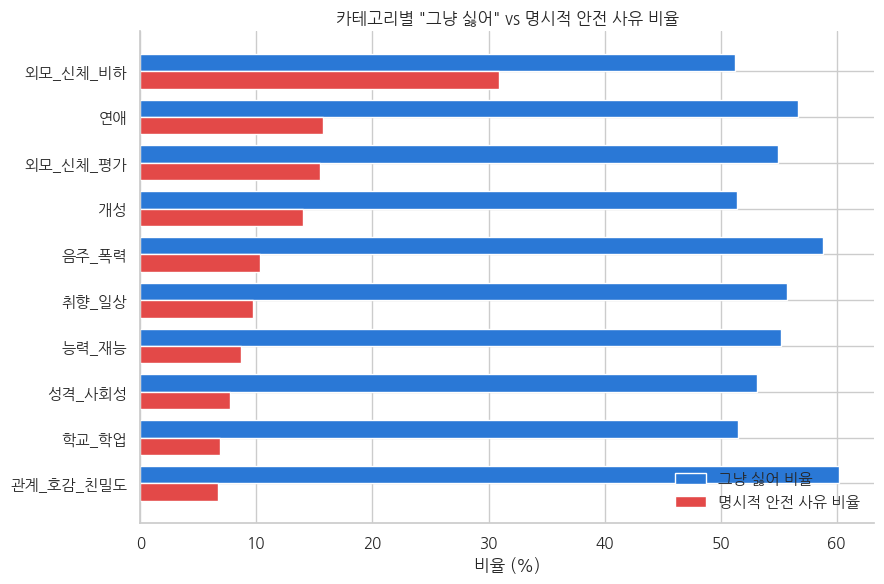

In [ ]:
# 싫어요·안전 사유 비중 차트
tm_order = tm_reason_check.sort_values('명시적안전사유_비율', ascending=True)['label']
tm_plot_df = tm_reason_check.set_index('label').loc[tm_order]
tm_fig, tm_ax = plt.subplots(figsize=(9, 6))
tm_y = range(len(tm_plot_df))
tm_bar_h = 0.38
tm_ax.barh([tm_i + tm_bar_h / 2 for tm_i in tm_y], tm_plot_df['그냥싫어_비율'], height=tm_bar_h, color='#2a78d6', label='그냥 싫어 비율')
tm_ax.barh([tm_i - tm_bar_h / 2 for tm_i in tm_y], tm_plot_df['명시적안전사유_비율'], height=tm_bar_h, color='#e34948', label='명시적 안전 사유 비율')
tm_ax.set_yticks(list(tm_y))
tm_ax.set_yticklabels(tm_plot_df.index)
tm_ax.set_xlabel('비율 (%)')
tm_ax.set_title('카테고리별 "그냥 싫어" vs 명시적 안전 사유 비율')
tm_ax.legend(loc='lower right', frameon=False)
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 외모·신체 비하에서도 ‘그냥 싫어’가 51.2%로 가장 많다. 다만 안전 사유 30.9%는 전체 평균 11.1%보다 높다. 이 비율의 분모는 해당 유형에 남은 피드백이다.


In [ ]:
# 외모·신체 비하 문구 확인
tm_sub = tm_reports_known[tm_reports_known['label'] == '외모_신체_비하']
tm_qtext = tm_exploded.set_index('question_id')['question']
tm_per_q = tm_sub.groupby('question_id').agg(총신고=('reason_raw', 'size'), 그냥싫어=('is_geunyang_sireo', 'sum'), 명시적안전=('is_explicit_safety', 'sum')).reset_index()
tm_per_q['question'] = tm_per_q['question_id'].map(tm_qtext)
tm_per_q['그냥싫어_비율'] = (tm_per_q['그냥싫어'] / tm_per_q['총신고'] * 100).round(1)
tm_per_q = tm_per_q.sort_values(['총신고', 'question_id'], ascending=[False, True])
tm_top2_share = tm_per_q.head(2)['그냥싫어'].sum() / tm_per_q['그냥싫어'].sum() * 100
print(f"상위 2개 문항이 카테고리 전체 '그냥 싫어' 690건 중 {tm_top2_share:.1f}%를 차지")
display(tm_per_q[['question_id', 'question', '총신고', '그냥싫어', '명시적안전', '그냥싫어_비율']])
plt.close('all')
_t7tc_collected = gc.collect()


상위 2개 문항이 카테고리 전체 '그냥 싫어' 690건 중 71.6%를 차지


,question_id,question,총신고,그냥싫어,명시적안전,그냥싫어_비율
0,410,발냄새가 호두과자 냄새일 것 같은 사람은?,803,383,289,47.7000
1,416,발가락에서 페브리즈향이 날 것 같은 사람은?,205,111,57,54.1000
2,470,발가락이 귀여울 것 같은 친구는?,154,81,38,52.6000
3,570,웃는 모습이 제일 웃긴 사람은?,91,59,18,64.8000
4,1035,사진빨을 잘받는 사람은?,38,20,4,52.6000
5,1524,얼굴을 가장 막 쓰는 사람은?,27,17,4,63.0000
6,2463,사진빨 잘 받는 친구는?,7,4,0,57.1000
7,2559,발에서 블루베리 향 날 것 같은 사람은?,6,4,1,66.7000
8,3345,아바타 닮은 것 같은 사람은?,5,4,1,80.0000
12,4047,퀸동주가 롤모델일 것 같은 사람은?,4,2,2,50.0000


- 외모·신체 비하의 ‘그냥 싫어’ 690건 중 71.6%가 ‘발냄새가 호두과자 냄새일 것 같은 사람’과 ‘발가락에서 페브리즈향이 날 것 같은 사람’ 두 문항에 집중됐다.


In [ ]:
# 음주·폭력 관련 문구 확인
tm_sub2 = tm_reports_known[tm_reports_known['label'] == '음주_폭력']
tm_per_q2 = tm_sub2.groupby('question_id').agg(총신고=('reason_raw', 'size'), 그냥싫어=('is_geunyang_sireo', 'sum'), 명시적안전=('is_explicit_safety', 'sum')).reset_index()
tm_per_q2['question'] = tm_per_q2['question_id'].map(tm_qtext)
tm_per_q2['그냥싫어_비율'] = (tm_per_q2['그냥싫어'] / tm_per_q2['총신고'] * 100).round(1)
tm_per_q2 = tm_per_q2.sort_values(['총신고', 'question_id'], ascending=[False, True])
tm_top2_share2 = tm_per_q2.head(2)['그냥싫어'].sum() / tm_per_q2['그냥싫어'].sum() * 100
print(f"상위 2개 문항이 카테고리 전체 그냥싫어 {int(tm_per_q2['그냥싫어'].sum())}건 중 {tm_top2_share2:.1f}%를 차지 (참고: 외모_신체_비하는 71.6%)")
display(tm_per_q2[['question_id', 'question', '총신고', '그냥싫어', '명시적안전', '그냥싫어_비율']])
plt.close('all')
_t7tc_collected = gc.collect()


상위 2개 문항이 카테고리 전체 그냥싫어 389건 중 20.6%를 차지 (참고: 외모_신체_비하는 71.6%)


,question_id,question,총신고,그냥싫어,명시적안전,그냥싫어_비율
5,478,범죄현장을 지나다가 억울하게 발자국을 남길 것 같은 사람은?,88,43,8,48.9000
0,224,나중에 술을 제일 잘 마실거 같은 사람은?,65,37,3,56.9000
2,334,술을 제일 잘 마실거 같은 사람은?,65,31,12,47.7000
4,435,패싸움이 났을 때 제일 먼저 부르고 싶은 사람은?,59,34,8,57.6000
1,225,나 대신 흑기사를 해줄 것 같은 사람은?,52,26,2,50.0000
3,420,"성인이 되고, 술이 제일 셀것 같은 사람은?",50,29,4,58.0000
6,530,나중에 술한잔 둘이서 하고 싶은 친구는?,42,31,1,73.8000
16,1545,게임하면서 지면 샷건 날려서 책상 뽀개먹을 것 같은 사람은?,40,22,8,55.0000
15,1541,어른돼서 가장 술찌일 것 같은 사람,37,21,6,56.8000
7,680,"나중에 술에 취해 ""자니...?""라고 보낼 것 같은 사람은?",24,18,2,75.0000


- 음주·폭력 유형은 상위 두 문항의 ‘그냥 싫어’ 비중이 20.6%다. 앞의 외모·신체 비하 71.6%보다 여러 문항에 분산돼 있다.

- 성인이 된 뒤의 음주를 묻는 질문과 싸움 관련 질문이 함께 있어, 유형 이름만으로 문구의 맥락을 대신하기는 어렵다.


**10개 학교로 범위를 맞춘 비교**

- 앞에서는 전체 학교의 피드백을 봤다. 이번에는 신고자의 현재 학교도 질문 배치 자료와 같은 10개 학교로 좁혔다.
- 가입자 마트에서 신고자의 학교를 연결했다. 현재 학교 정보이므로 피드백을 남길 당시의 학교와 다를 수 있다.
- 건수가 적고 실제 열람 횟수도 없어, 이 비교는 참고용으로만 본다.


In [ ]:
# 신고자 학교 연결·범위 점검
tm_TEN_SCHOOLS = [1719, 5520, 4426, 5491, 369, 271, 4516, 5372, 1478, 352]
tm_actor_ids = pd.Index(pd.to_numeric(tm_reports_known['actor_user_id'], errors='coerce').dropna().astype('int64').unique())
tm_actor_parts = []
for tm_actor_chunk in tm_load_mart(
    'mart_user_acquisition_profile_v2_clean',
    usecols=['user_id', 'current_school_id'],
    dtype={'user_id': 'Int64', 'current_school_id': 'string'},
    chunksize=100000,
):
    tm_actor_chunk = tm_actor_chunk.loc[tm_actor_chunk['user_id'].isin(tm_actor_ids)].copy()
    tm_actor_chunk['current_school_id'] = pd.to_numeric(tm_actor_chunk['current_school_id'], errors='coerce')
    if not tm_actor_chunk.empty:
        tm_actor_parts.append(tm_actor_chunk)
tm_actor_prof = pd.concat(tm_actor_parts, ignore_index=True) if tm_actor_parts else pd.DataFrame({'user_id': pd.Series(dtype='Int64'), 'current_school_id': pd.Series(dtype='Float64')})
if tm_actor_prof['user_id'].duplicated().any():
    raise ValueError('신고자 학교 연결표의 사용자 ID가 중복입니다.')
tm_actor_prof = tm_actor_prof.rename(columns={'user_id': 'actor_user_id', 'current_school_id': 'actor_school_id'})
tm_reports_for_school = tm_reports_known.copy()
tm_reports_for_school['actor_user_id'] = pd.to_numeric(tm_reports_for_school['actor_user_id'], errors='coerce').astype('Int64')
tm_reports_with_school = tm_reports_for_school.merge(tm_actor_prof, on='actor_user_id', how='left', validate='many_to_one')
assert len(tm_reports_with_school) == len(tm_reports_known)
tm_reports_known_10 = tm_reports_with_school.loc[tm_reports_with_school['actor_school_id'].isin(tm_TEN_SCHOOLS)].copy()
tm_school_scope_qa = pd.DataFrame([
    ('전체 라벨 연결 피드백', len(tm_reports_known)),
    ('신고자 학교 연결', int(tm_reports_with_school['actor_school_id'].notna().sum())),
    ('학교 연결 불가', int(tm_reports_with_school['actor_school_id'].isna().sum())),
    ('10개 학교 피드백', len(tm_reports_known_10)),
], columns=['구분', '건수'])
display(tm_school_scope_qa)
del tm_actor_parts, tm_actor_chunk, tm_actor_prof, tm_reports_for_school, tm_reports_with_school, tm_actor_ids
_t7tc_collected = gc.collect()


,구분,건수
0,전체 라벨 연결 피드백,50926
1,신고자 학교 연결,50926
2,학교 연결 불가,0
3,10개 학교 피드백,382


- 라벨이 연결된 전체 피드백 50,926건 중 신고자가 10개 학교 소속인 기록은 382건이다. 전체의 약 0.8%만 남는다.
- 학교가 연결되지 않은 기록은 10개 학교에 포함하지 않았다. 사용자 ID 중복으로 피드백이 늘어나지 않는지도 확인했다.


In [ ]:
# 같은 학교 범위의 질문조각 대비 피드백
tm_rate_rows = []
for tm_cat, tm_sub in tm_exploded.groupby('label'):
    tm_qids = tm_sub['question_id'].astype(int)
    tm_n_exposure = tm_exposure_count.reindex(tm_qids).sum()
    tm_n_reports_10 = tm_reports_known_10[tm_reports_known_10['label'] == tm_cat].shape[0]
    tm_rate_rows.append({'카테고리': tm_cat, '노출횟수(10개교)': int(tm_n_exposure), '신고건수(신고자도 10개교)': tm_n_reports_10, '신고율_per_1000노출(10개교 통일)': round(tm_n_reports_10 / tm_n_exposure * 1000, 2) if tm_n_exposure else float('nan')})
tm_rate_10 = pd.DataFrame(tm_rate_rows).sort_values('신고율_per_1000노출(10개교 통일)', ascending=False).reset_index(drop=True)
display(tm_rate_10)
_t7tc_collected = gc.collect()


,카테고리,노출횟수(10개교),신고건수(신고자도 10개교),신고율_per_1000노출(10개교 통일)
0,외모_신체_비하,6059,12,1.9800
1,외모_신체_평가,148725,67,0.4500
2,연애,103700,35,0.3400
3,개성,99872,33,0.3300
4,성격_사회성,250319,81,0.3200
5,능력_재능,187515,55,0.2900
6,취향_일상,133805,35,0.2600
7,관계_호감_친밀도,242176,54,0.2200
8,음주_폭력,16091,3,0.1900
9,학교_학업,38822,7,0.1800


- 외모·신체 비하는 질문조각 6,059건에 피드백 12건으로, 1,000조각당 1.98건이다. 전체 학교의 피드백을 섞었던 계산과 구분했다.
- 유형별 피드백이 3~81건으로 적어 한두 건에도 순위가 달라질 수 있다. 실제 위해 발생률로 해석하지 않는다.


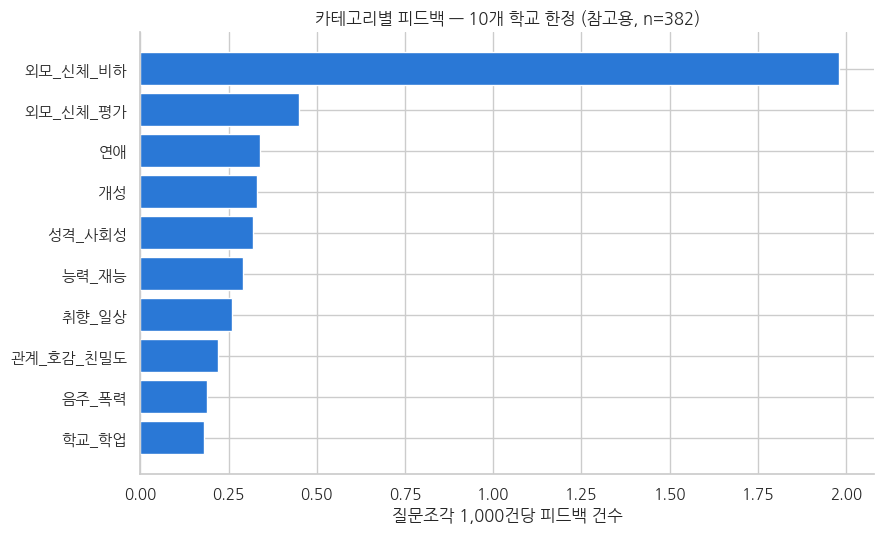

In [ ]:
# 10개 학교 기준 피드백 비교 차트
tm_fig, tm_ax = plt.subplots(figsize=(9, 5.5))
tm_order = tm_rate_10.sort_values('신고율_per_1000노출(10개교 통일)', ascending=True)
tm_ax.barh(tm_order['카테고리'], tm_order['신고율_per_1000노출(10개교 통일)'], color='#2a78d6')
tm_ax.set_xlabel('질문조각 1,000건당 피드백 건수')
tm_ax.set_title(f'카테고리별 피드백 — 10개 학교 한정 (참고용, n={len(tm_reports_known_10):,})')
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close("all")
_t7tc_collected = gc.collect()


- 학교 범위를 맞춘 뒤에도 외모·신체 비하가 가장 높다. 질문당 건수와 잠재 안전 사유 비중도 함께 보며 검토 순서를 정할 수 있다.
- 다만 배치 기록과 피드백을 개별 열람 사건으로 연결한 것은 아니다. 다음 모델링에서는 질문별 안전 피드백 이력의 유무를 따로 사용한다.


### 3-6-4. 안전 피드백 이력 분류

- 질문 유형·문구를 사용한 모델과 키워드 규칙의 분류 성능을 비교했다.
- 예측 대상은 누적 안전 피드백 이력의 유무다. 실제 유해성이나 미래 신고 확률을 뜻하지 않으며, 단어 계수는 인과효과가 아니다.


In [ ]:
# 질문별 안전 피드백 라벨
tm_q_level = tm_reports_known.groupby('question_id')['is_explicit_safety'].sum().reindex(tm_exploded['question_id']).fillna(0)
tm_q_level = tm_q_level.to_frame('n_safety_reports').reset_index()
tm_q_level['label'] = tm_q_level['question_id'].map(tm_cat_map)
tm_q_level['question'] = tm_q_level['question_id'].map(tm_exploded.set_index('question_id')['question'])
tm_q_level['has_safety_report'] = (tm_q_level['n_safety_reports'] > 0).astype(int)
print('질문 수:', len(tm_q_level))
print(f"has_safety_report=1 비율: {tm_q_level['has_safety_report'].mean():.1%}  (전체 대비 비교적 균형 잡힌 편)")
display(tm_q_level.groupby('label')['has_safety_report'].agg(['sum', 'count', 'mean']).sort_values('mean', ascending=False))
plt.close('all')
_t7tc_collected = gc.collect()


질문 수: 3088
has_safety_report=1 비율: 39.8%  (전체 대비 비교적 균형 잡힌 편)


,sum,count,mean
label,,,
음주_폭력,18,21,0.8571
외모_신체_비하,10,15,0.6667
연애,153,299,0.5117
외모_신체_평가,157,338,0.4645
개성,81,195,0.4154
학교_학업,37,91,0.4066
성격_사회성,223,565,0.3947
관계_호감_친밀도,241,629,0.3831
취향_일상,172,513,0.3353


- 3,088개 질문 ID 중 안전 피드백이 한 번이라도 붙은 비율은 39.8%다. 유형별로는 음주·폭력 85.7%, 외모·신체 비하 66.7%, 연애 51.2% 순이다.
- 질문별 누적 유무를 센 값이다. 앞의 피드백 행 기준 사유 비중이나 질문당 피드백 건수와는 분모가 다르다.


In [ ]:
# 분류 라이브러리 버전 확인
print('scikit-learn:', sklearn.__version__)
plt.close('all')
_t7tc_collected = gc.collect()


scikit-learn: 1.6.1


In [ ]:
# 분류·문구 모델 교차검증
tm_X = tm_q_level[['label', 'question']]
tm_y = tm_q_level['has_safety_report']
tm_X_train, tm_X_test, tm_y_train, tm_y_test = train_test_split(tm_X, tm_y, test_size=0.2, stratify=tm_y, random_state=42)
tm_prep_full = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['label']), ('text', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), max_features=300, min_df=10), 'question')])
tm_pipe_full = Pipeline([('prep', tm_prep_full), ('clf', LogisticRegression(max_iter=2000, C=0.5, class_weight='balanced'))])
tm_prep_cat = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['label'])])
tm_pipe_cat = Pipeline([('prep', tm_prep_cat), ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))])
tm_cv_full = cross_val_score(tm_pipe_full, tm_X, tm_y, cv=5, scoring='roc_auc')
tm_cv_cat = cross_val_score(tm_pipe_cat, tm_X, tm_y, cv=5, scoring='roc_auc')
print(f'카테고리만 모델      5-fold CV ROC-AUC: {tm_cv_cat.mean():.3f} (+/-{tm_cv_cat.std():.3f})')
print(f'카테고리+텍스트 모델  5-fold CV ROC-AUC: {tm_cv_full.mean():.3f} (+/-{tm_cv_full.std():.3f})')
print('(참고: ROC-AUC 0.5 = 랜덤 추측 수준, 1.0 = 완벽한 분류)')
plt.close('all')
_t7tc_collected = gc.collect()


카테고리만 모델      5-fold CV ROC-AUC: 0.564 (+/-0.025)
카테고리+텍스트 모델  5-fold CV ROC-AUC: 0.603 (+/-0.026)
(참고: ROC-AUC 0.5 = 랜덤 추측 수준, 1.0 = 완벽한 분류)


- 유형만 사용한 교차검증 ROC-AUC는 0.564, 문구를 더하면 0.603이다. 텍스트가 일부 정보를 보탰지만 상승 폭은 크지 않다.

- 첫 실험은 질문 ID 단위로 나눴다. 비슷한 문구가 양쪽에 섞일 가능성은 뒤의 의미군 단위 평가에서 줄였다.


In [ ]:
# 첫 모델 평가
tm_pipe_full.fit(tm_X_train, tm_y_train)
tm_pred = tm_pipe_full.predict(tm_X_test)
tm_proba = tm_pipe_full.predict_proba(tm_X_test)[:, 1]
print(classification_report(tm_y_test, tm_pred, digits=3, target_names=['안전신고 없음(0)', '안전신고 있음(1)']))
print('holdout ROC-AUC:', round(float(roc_auc_score(tm_y_test, tm_proba)), 3))
print('\nconfusion matrix (행=실제, 열=예측):')
print(confusion_matrix(tm_y_test, tm_pred))
print(f"\n참고: 아무것도 안 걸러내고 전부 '안전신고 없음'으로 찍는 다수결 기준 정확도: {(tm_y_test == 0).mean():.3f} / 모델 정확도: {(tm_pred == tm_y_test).mean():.3f}")
plt.close('all')
_t7tc_collected = gc.collect()


              precision    recall  f1-score   support

  안전신고 없음(0)      0.678     0.559     0.613       372
  안전신고 있음(1)      0.473     0.598     0.528       246

    accuracy                          0.574       618
   macro avg      0.575     0.578     0.570       618
weighted avg      0.596     0.574     0.579       618

holdout ROC-AUC: 0.624

confusion matrix (행=실제, 열=예측):
[[208 164]
 [ 99 147]]

참고: 아무것도 안 걸러내고 전부 '안전신고 없음'으로 찍는 다수결 기준 정확도: 0.602 / 모델 정확도: 0.574


- 보류 표본 ROC-AUC는 0.624다. 정확도 57.4%는 모두 ‘안전 피드백 없음’으로 분류했을 때의 60.2%보다 낮았다.


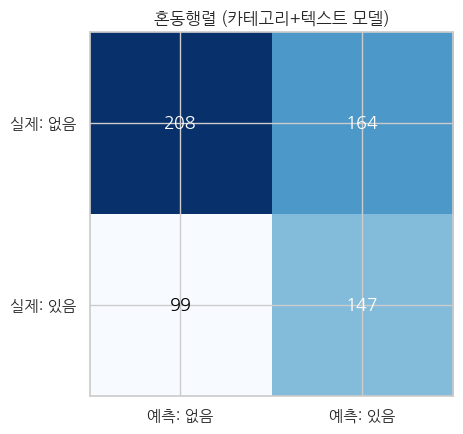

In [ ]:
# 첫 모델 혼동행렬
tm_fig, tm_ax = plt.subplots(figsize=(5, 4.5))
tm_cm = confusion_matrix(tm_y_test, tm_pred)
tm_im = tm_ax.imshow(tm_cm, cmap='Blues')
tm_ax.set_xticks([0, 1])
tm_ax.set_xticklabels(['예측: 없음', '예측: 있음'])
tm_ax.set_yticks([0, 1])
tm_ax.set_yticklabels(['실제: 없음', '실제: 있음'])
for tm_i in range(2):
    for tm_j in range(2):
        tm_ax.text(tm_j, tm_i, tm_cm[tm_i, tm_j], ha='center', va='center', color='white' if tm_cm[tm_i, tm_j] > tm_cm.max() / 2 else 'black', fontsize=13)
tm_ax.set_title('혼동행렬 (카테고리+텍스트 모델)')
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 안전 피드백 이력이 있는 질문 246개 중 99개를 놓쳤고, 이력이 없는 질문 164개를 검토 대상으로 분류했다.


In [ ]:
# 분류·문구 계수 확인
tm_clf = tm_pipe_full.named_steps['clf']
tm_feat_names = tm_pipe_full.named_steps['prep'].get_feature_names_out()
tm_coefs = tm_clf.coef_[0]
tm_order = np.argsort(tm_coefs)
tm_top_up = [(tm_feat_names[tm_i], tm_coefs[tm_i]) for tm_i in tm_order[::-1][:15]]
tm_top_down = [(tm_feat_names[tm_i], tm_coefs[tm_i]) for tm_i in tm_order[:15]]
print('안전신고 가능성을 높이는 방향으로 작용하는 상위 피처:')
for tm_name, tm_c in tm_top_up:
    print(f'  {tm_name:20s} {tm_c:+.3f}')
print('\n안전신고 가능성을 낮추는 방향으로 작용하는 상위 피처:')
for tm_name, tm_c in tm_top_down:
    print(f'  {tm_name:20s} {tm_c:+.3f}')
plt.close('all')
_t7tc_collected = gc.collect()


안전신고 가능성을 높이는 방향으로 작용하는 상위 피처:
  text__ 매             +1.086
  cat__label_음주_폭력     +1.034
  text__거              +0.816
  text__이              +0.794
  text__일              +0.772
  text__매일             +0.741
  text__에게             +0.740
  text__에게             +0.704
  text__ 1             +0.693
  text__ 지             +0.666
  text__ 부             +0.614
  text__ 주             +0.591
  text__울              +0.583
  text__ 얘             +0.579
  text__ 수             +0.567

안전신고 가능성을 낮추는 방향으로 작용하는 상위 피처:
  text__람              -1.003
  text__사람             -0.977
  text__ 하             -0.751
  text__주고             -0.705
  text__ 나             -0.572
  text__ 말             -0.568
  text__주고             -0.565
  text__만              -0.542
  text__리              -0.541
  text__ 것             -0.526
  text__ 재             -0.523
  text__ 생             -0.519
  text__ 선             -0.510
  text__ 것             -0.508
  text__기              -0.500


- 양의 계수 상위에는 음주·폭력 라벨과 ‘매일’ 등이 있다. ‘거’, ‘이’ 같은 짧은 문자 조각도 함께 올라와 있어 의미만으로 설명하기 어려운 특징이 섞였다.


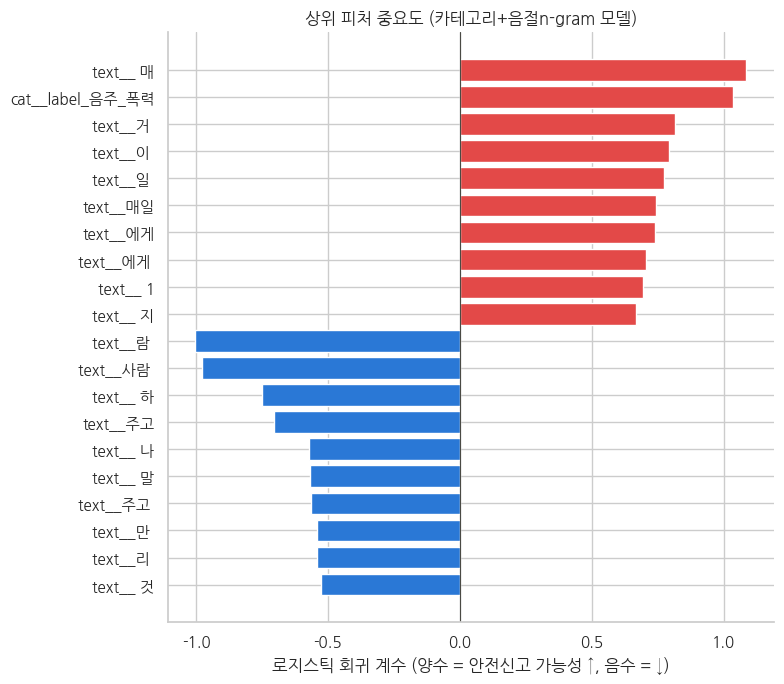

In [ ]:
# 문구 특징 계수 차트
tm_N_SHOW = 10
tm_top_up_n = tm_top_up[:tm_N_SHOW]
tm_top_down_n = tm_top_down[:tm_N_SHOW]
tm_plot_feats = list(reversed(tm_top_down_n)) + list(reversed(tm_top_up_n))
tm_names = [tm_n for tm_n, tm__ in tm_plot_feats]
tm_vals = [tm_v for tm__, tm_v in tm_plot_feats]
tm_colors = ['#2a78d6' if tm_v < 0 else '#e34948' for tm_v in tm_vals]
tm_fig, tm_ax = plt.subplots(figsize=(8, 7))
tm_ax.barh(tm_names, tm_vals, color=tm_colors)
tm_ax.axvline(0, color='#4a4a44', linewidth=0.8)
tm_ax.set_xlabel('로지스틱 회귀 계수 (양수 = 안전신고 가능성 ↑, 음수 = ↓)')
tm_ax.set_title('상위 피처 중요도 (카테고리+음절n-gram 모델)')
for tm_spine in ['top', 'right']:
    tm_ax.spines[tm_spine].set_visible(False)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- ‘사람’은 음의 계수 쪽에, 음주·폭력 라벨은 양의 계수 쪽에 놓인다. 자주 반복된 문장 형태까지 학습한 결과여서 이 목록을 그대로 금칙어·허용어 사전으로 쓰기에는 무리가 있다.


In [ ]:
# 형태소·위험 표현 처리
tm_kiwi = Kiwi(num_workers=1)
tm_CONTENT_TAGS_ADV = ('NNG', 'NNP', 'VV', 'VA', 'MAG')

def tm_morph_tokens_adv(tm_text):
    tm_out = []
    for tm_t in tm_kiwi.tokenize(str(tm_text)):
        if tm_t.tag in ('VV', 'VA'):
            tm_out.append(tm_t.form + '다')
        elif tm_t.tag in tm_CONTENT_TAGS_ADV:
            tm_out.append(tm_t.form)
    return tm_out
plt.close('all')
_t7tc_collected = gc.collect()


In [ ]:
# 형태소 기반 위험 표현 분포
tm_ALCOHOL_KEYWORDS = ['술', '음주', '흑기사', '주사', '담배', '숙취', '소주', '맥주', '막걸리', '와인', '위스키', '샴페인', '폭탄주', '샷건', '술버릇', '만취', '해장', '음주운전', '술자리', '술집']
tm_VIOLENCE_KEYWORDS = ['싸움', '때리다', '범죄', '폭력', '패다', '패싸움', '구타', '폭행', '학교폭력']
tm_RISK_KEYWORDS = set(tm_ALCOHOL_KEYWORDS + tm_VIOLENCE_KEYWORDS)

def tm_has_risk_keyword(tm_text):
    tm_toks = set(tm_morph_tokens_adv(tm_text))
    return int(len(tm_toks & tm_RISK_KEYWORDS) > 0)
tm_q_level['has_risk_keyword'] = tm_q_level['question'].apply(tm_has_risk_keyword)
print(f"위험 키워드가 포함된 질문 수: {tm_q_level['has_risk_keyword'].sum()} / {len(tm_q_level)}")
print('\n위험 키워드 포함 여부 x 카테고리 (건수):')
display(pd.crosstab(tm_q_level['label'], tm_q_level['has_risk_keyword']))
print('\n위험 키워드 포함 여부 x 안전신고 여부 (행 기준 비율):')
display(pd.crosstab(tm_q_level['has_risk_keyword'], tm_q_level['has_safety_report'], normalize='index').round(3))
tm_still_flagged = tm_q_level[tm_q_level['label'] == '음주_폭력']['has_risk_keyword']
print(f'\n[키워드 탐지 범위] 음주_폭력 카테고리 중 키워드로 잡히는 비율: {tm_still_flagged.mean():.1%} ({tm_still_flagged.sum()}/{len(tm_still_flagged)})')
plt.close('all')
_t7tc_collected = gc.collect()


위험 키워드가 포함된 질문 수: 20 / 3088

위험 키워드 포함 여부 x 카테고리 (건수):


has_risk_keyword,0,1
label,,
개성,194,1
관계_호감_친밀도,628,1
능력_재능,422,0
성격_사회성,564,1
연애,299,0
외모_신체_비하,15,0
외모_신체_평가,338,0
음주_폭력,6,15
취향_일상,511,2



위험 키워드 포함 여부 x 안전신고 여부 (행 기준 비율):


has_safety_report,0,1
has_risk_keyword,,
0,0.6040,0.3960
1,0.2500,0.7500



[회귀 확인] 음주_폭력 카테고리 중 키워드로 잡히는 비율: 71.4% (15/21)


- 키워드 규칙에 걸린 질문은 3,088개 중 20개이며, 이 중 음주·폭력 유형은 15개다. 규칙에 걸린 질문의 75.0%에 안전 피드백 이력이 있었다.
- 외모·신체 비하 유형에서는 탐지된 질문이 없었다.


In [ ]:
# 단순 모델·규칙 결합 비교
tm_test_hard_rule = tm_q_level.loc[tm_X_test.index, 'has_risk_keyword']
tm_hybrid_pred = ((tm_proba >= 0.5) | (tm_test_hard_rule == 1)).astype(int)
print('=== 모델 단독 (threshold=0.5) ===')
print(classification_report(tm_y_test, tm_pred, digits=3, target_names=['안전신고 없음(0)', '안전신고 있음(1)']))
print('\n=== 모델 + 음주/폭력 하드룰 하이브리드 ===')
print(classification_report(tm_y_test, tm_hybrid_pred, digits=3, target_names=['안전신고 없음(0)', '안전신고 있음(1)']))
tm_n_rescued = ((tm_test_hard_rule == 1) & (tm_pred == 0) & (tm_y_test == 1)).sum()
tm_n_new_fp = ((tm_test_hard_rule == 1) & (tm_pred == 0) & (tm_y_test == 0)).sum()
print(f'\n하드룰이 추가로 구제한 건수(모델은 놓쳤지만 하드룰이 잡음, 실제로 안전신고 있음): {tm_n_rescued}')
print(f'하드룰 때문에 새로 생긴 오탐(모델은 0인데 하드룰 때문에 1, 실제는 안전신고 없음): {tm_n_new_fp}')
plt.close('all')
_t7tc_collected = gc.collect()


=== 모델 단독 (threshold=0.5) ===
              precision    recall  f1-score   support

  안전신고 없음(0)      0.678     0.559     0.613       372
  안전신고 있음(1)      0.473     0.598     0.528       246

    accuracy                          0.574       618
   macro avg      0.575     0.578     0.570       618
weighted avg      0.596     0.574     0.579       618


=== 모델 + 음주/폭력 하드룰 하이브리드 ===
              precision    recall  f1-score   support

  안전신고 없음(0)      0.678     0.559     0.613       372
  안전신고 있음(1)      0.473     0.598     0.528       246

    accuracy                          0.574       618
   macro avg      0.575     0.578     0.570       618
weighted avg      0.596     0.574     0.579       618


하드룰이 추가로 구제한 건수(모델은 놓쳤지만 하드룰이 잡음, 실제로 안전신고 있음): 0
하드룰 때문에 새로 생긴 오탐(모델은 0인데 하드룰 때문에 1, 실제는 안전신고 없음): 0


- 규칙을 더해도 보류 표본의 정밀도·재현율은 그대로였다. 추가로 찾은 안전 피드백 질문도, 새로 생긴 오탐도 0건이다. 이번 조합에서는 개선이 없었다.


In [ ]:
# 규칙 추가로 달라진 문구 확인
tm_detail_df = tm_X_test.copy()
tm_detail_df['actual'] = tm_y_test.values
tm_detail_df['model_pred'] = tm_pred
tm_detail_df['hard_rule'] = tm_test_hard_rule.values
tm_detail_df['hybrid_pred'] = tm_hybrid_pred
tm_rescued = tm_detail_df[(tm_detail_df['hard_rule'] == 1) & (tm_detail_df['model_pred'] == 0) & (tm_detail_df['actual'] == 1)]
tm_new_fp = tm_detail_df[(tm_detail_df['hard_rule'] == 1) & (tm_detail_df['model_pred'] == 0) & (tm_detail_df['actual'] == 0)]
print(f"하드룰이 구제한 질문 ({len(tm_rescued)}건 — 모델은 '안전'으로 놓쳤지만 실제로 안전신고가 있었음):")
display(tm_rescued[['label', 'question']])
print(f"\n하드룰 때문에 새로 오탐이 된 질문 ({len(tm_new_fp)}건 — 모델은 '안전'으로 봤고 실제로도 신고 없었는데, 하드룰이 위험으로 바꿈):")
display(tm_new_fp[['label', 'question']])
plt.close('all')
_t7tc_collected = gc.collect()


하드룰이 구제한 질문 (0건 — 모델은 '안전'으로 놓쳤지만 실제로 안전신고가 있었음):


,label,question



하드룰 때문에 새로 오탐이 된 질문 (0건 — 모델은 '안전'으로 봤고 실제로도 신고 없었는데, 하드룰이 위험으로 바꿈):


,label,question


- 규칙 추가로 예측이 바뀐 사례가 없어 두 예시 표는 비어 있다.


### 3-6-5. 검토 기준과 심화 분석 표본

- 점수 기준별 재현율과 검토량을 비교하고, 사용자·문구의 반복 피드백을 정리했다.


In [ ]:
# 안전 검토 임계값 비교
tm_thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
tm_sweep_rows = []
for tm_th in tm_thresholds:
    tm_pred_th = (tm_proba >= tm_th).astype(int)
    tm_sweep_rows.append({'threshold': tm_th, '정밀도(검토 중 안전 피드백 이력 비율)': round(precision_score(tm_y_test, tm_pred_th, zero_division=0), 3), '재현율(안전 피드백 이력 중 탐지 비율)': round(recall_score(tm_y_test, tm_pred_th), 3), '검토로 보내는 비율(전체 중)': round(tm_pred_th.mean(), 3)})
tm_sweep_df = pd.DataFrame(tm_sweep_rows)
display(tm_sweep_df)
plt.close('all')
_t7tc_collected = gc.collect()


,threshold,정밀도(검토 중 안전 피드백 이력 비율),재현율(안전 피드백 이력 중 탐지 비율),검토로 보내는 비율(전체 중)
0,0.3000,0.4020,0.9760,0.9660
1,0.4000,0.4210,0.8460,0.7990
2,0.5000,0.4730,0.5980,0.5030
3,0.6000,0.5860,0.3050,0.2070
4,0.7000,0.7040,0.0770,0.0440


- 기준 0.3에서는 안전 피드백 이력 질문의 97.6%를 찾지만 전체 질문의 96.6%를 검토 대상으로 분류한다. 기준 0.5에서는 검토 대상 50.3%, 재현율 59.8%다.
- 놓치는 질문 수와 검토량을 함께 고려해야 한다.


In [ ]:
# 게시·검토·제한 기준 점검
tm_REVIEW_THRESHOLD = 0.5

def tm_assign_tier(tm_has_kw, tm_p):
    if tm_has_kw == 1:
        return '제한(즉시 검토, 하드룰)'
    elif tm_p >= tm_REVIEW_THRESHOLD:
        return '검토'
    else:
        return '게시'
tm_tier = pd.Series([tm_assign_tier(tm_hk, tm_p) for tm_hk, tm_p in zip(tm_test_hard_rule.values, tm_proba)], index=tm_X_test.index, name='운영_등급')
tm_tier_summary = pd.DataFrame({'등급': tm_tier, '실제_안전신고': tm_y_test.values})
print('=== 등급별 분포 및 실제 안전신고 비율 ===')
display(tm_tier_summary.groupby('등급').agg(질문수=('실제_안전신고', 'size'), 실제_안전신고_있음=('실제_안전신고', 'sum'), 안전신고_비율=('실제_안전신고', 'mean')).round(3))
tm_caught = tm_tier_summary.loc[tm_tier_summary['등급'] != '게시', '실제_안전신고'].sum()
tm_total_positive = tm_tier_summary['실제_안전신고'].sum()
tm_residual_risk = tm_tier_summary.loc[tm_tier_summary['등급'] == '게시', '실제_안전신고'].mean()
print(f"\n전체 안전신고 {tm_total_positive}건 중 '게시'가 아닌 쪽(검토+제한)에서 잡아낸 비율: {tm_caught / tm_total_positive:.1%}")
print(f"'게시'로 자동 승인된 것들 중에도 실제 안전신고가 있었던 비율(잔여 위험): {tm_residual_risk:.1%}")
plt.close('all')
_t7tc_collected = gc.collect()


=== 등급별 분포 및 실제 안전신고 비율 ===


,질문수,실제_안전신고_있음,안전신고_비율
등급,,,
검토,305,142,0.4660
게시,307,99,0.3220
"제한(즉시 검토, 하드룰)",6,5,0.8330



전체 안전신고 246건 중 '게시'가 아닌 쪽(검토+제한)에서 잡아낸 비율: 59.8%
'게시'로 자동 승인된 것들 중에도 실제 안전신고가 있었던 비율(잔여 위험): 32.2%


- 안전 피드백 이력이 있는 질문 246개 중 147개(59.8%)를 검토·제한 등급으로 분류했다. 게시 등급 307개 중 99개(32.2%)에도 안전 피드백 이력이 있었다.
- 과거 신고 이력에 대한 분류 결과이며, 실제 사전 차단 효과나 자동 승인의 안전성을 입증하지 않는다.


In [ ]:
# 첫 Trust 결과·임시 변수 정리
trust_model_results = {name: globals().get('tm_' + name) for name in ['report_summary', 'tier_summary', 'rate_10', 'school_scope_qa']}
t7tc_release('tm_')


파트 임시 데이터 메모리 정리 완료: tm_


In [ ]:
# Trust 문구 심화 분석 설정
td_SEED = 260916
td_RNG = np.random.default_rng(td_SEED)
td_sm = sys.modules['statsmodels.api']
td_SAFETY_PATH = t7tc_clean_path('mart_safety_event_v2')
td_QUESTION_LOOKUP_PATH = t7tc_clean_path('mart_question_exposure')
td_TEXT_FEATURE_PATH = T7TC_CONTENT / 'unique_question_text_features_bert.csv'
td_TEXT_THEME_PATH = T7TC_CONTENT / 'final_deep/01c_text_level_adjusted_scores.csv'
td_EMBEDDING_PATH = T7TC_CONTENT / 'cache/ko_sroberta_question_embeddings.npz'
td_MANUAL_LABEL_PATH = TRUST_LABEL_PATH
td_content_assets = globals().get('team7_content_assets', {})
td_content_fallbacks = {'text_features': td_TEXT_FEATURE_PATH, 'theme_map': td_TEXT_THEME_PATH, 'texts': td_EMBEDDING_PATH, 'embeddings': td_EMBEDDING_PATH}
td_missing_assets = [key for key, path in td_content_fallbacks.items() if key not in td_content_assets and (not path.is_file())]
if td_missing_assets:
    raise RuntimeError('3-3. Content를 먼저 실행해야 합니다. 필요한 결과: ' + ', '.join(td_missing_assets))
t7tc_style()

def td_normalize_text(td_value):
    td_text = unicodedata.normalize('NFKC', str(td_value)).lower().strip()
    td_text = re.sub('[\\s\\u200b]+', ' ', td_text)
    td_text = re.sub('[^0-9a-z가-힣 ]+', '', td_text)
    return re.sub('\\s+', ' ', td_text).strip()

def td_savefig(td_name):
    td_path = td_name
    plt.tight_layout()
    plt.show()
    plt.close()
    return td_path

def td_bh_adjust(td_pvalues):
    td_p = np.asarray(td_pvalues, dtype=float)
    td_adjusted = np.full(len(td_p), np.nan)
    td_valid = np.isfinite(td_p)
    if td_valid.any():
        td_adjusted[td_valid] = multipletests(td_p[td_valid], method='fdr_bh')[1]
    return td_adjusted

def td_proportion_ci(td_success, td_total, td_alpha=0.05):
    td_success = np.asarray(td_success, dtype=float)
    td_total = np.asarray(td_total, dtype=float)
    td_lower = scipy_stats.beta.ppf(td_alpha / 2, td_success + 0.5, td_total - td_success + 0.5)
    td_upper = scipy_stats.beta.ppf(1 - td_alpha / 2, td_success + 0.5, td_total - td_success + 0.5)
    return (td_lower, td_upper)

def td_eval_binary(td_y, td_probability, td_threshold=0.5, td_sample_weight=None):
    td_y = np.asarray(td_y, dtype=int)
    td_probability = np.asarray(td_probability, dtype=float)
    td_prediction = td_probability >= td_threshold
    td_order = np.argsort(-td_probability)
    td_top_n = max(1, int(np.ceil(len(td_y) * 0.1)))
    if np.allclose(td_probability, td_probability[0]):
        td_top_precision = float(np.average(td_y, weights=td_sample_weight))
    else:
        td_weights = None if td_sample_weight is None else np.asarray(td_sample_weight)[td_order[:td_top_n]]
        td_top_precision = float(np.average(td_y[td_order[:td_top_n]], weights=td_weights))
    return {'pr_auc': average_precision_score(td_y, td_probability, sample_weight=td_sample_weight), 'roc_auc': roc_auc_score(td_y, td_probability, sample_weight=td_sample_weight), 'balanced_accuracy': balanced_accuracy_score(td_y, td_prediction, sample_weight=td_sample_weight), 'f1': f1_score(td_y, td_prediction, sample_weight=td_sample_weight, zero_division=0), 'precision': precision_score(td_y, td_prediction, sample_weight=td_sample_weight, zero_division=0), 'recall': recall_score(td_y, td_prediction, sample_weight=td_sample_weight, zero_division=0), 'brier': brier_score_loss(td_y, td_probability, sample_weight=td_sample_weight), 'precision_at_top_10pct': td_top_precision, 'threshold': td_threshold}

def td_best_bacc_threshold(td_y, td_probability):
    td_candidates = np.unique(np.r_[np.linspace(0.05, 0.95, 181), np.quantile(td_probability, np.linspace(0, 1, 101))])
    td_scores = [balanced_accuracy_score(td_y, td_probability >= td_threshold) for td_threshold in td_candidates]
    return float(td_candidates[int(np.argmax(td_scores))])
print('텍스트 심화 분석 연결 완료')
plt.close('all')
_t7tc_collected = gc.collect()


텍스트 심화 분석 연결 완료


In [ ]:
# 질문 피드백·문구 연결 점검
td_safety = pd.read_csv(td_SAFETY_PATH)
td_question_lookup = pd.read_csv(td_QUESTION_LOOKUP_PATH, usecols=['question_id', 'question_text']).dropna(subset=['question_id', 'question_text']).drop_duplicates('question_id')
td_question_lookup['question_id'] = pd.to_numeric(td_question_lookup['question_id'], errors='coerce').astype('Int64')
td_question_lookup['normalized_text'] = td_question_lookup['question_text'].map(td_normalize_text)
td_feedback = td_safety.loc[td_safety['record_type'].eq('QUESTION_FEEDBACK_OR_REPORT')].copy()
td_feedback['question_id'] = pd.to_numeric(td_feedback['question_id'], errors='coerce').astype('Int64')
td_feedback['potential_safety'] = td_feedback['potential_safety_related_rule_flag'].fillna(0).astype(int)
td_feedback['event_at'] = pd.to_datetime(td_feedback['event_at_raw'], errors='coerce')
td_feedback['event_month'] = td_feedback['event_at'].dt.to_period('M').astype(str)
td_feedback = td_feedback.merge(td_question_lookup[['question_id', 'question_text', 'normalized_text']], on='question_id', how='left', validate='many_to_one')
td_scope = pd.DataFrame([('안전 마트 전체 행', len(td_safety)), ('질문 피드백·신고 채널 행', len(td_feedback)), ('질문 문구 연결 행', td_feedback['normalized_text'].notna().sum()), ('문구 미연결 행', td_feedback['normalized_text'].isna().sum()), ('피드백 사용자', td_feedback['actor_user_id'].nunique()), ('연결 질문 ID', td_feedback.loc[td_feedback['normalized_text'].notna(), 'question_id'].nunique()), ('정규화 고유 문구', td_feedback['normalized_text'].nunique()), ('잠재 안전 사유 행', td_feedback['potential_safety'].sum()), ('분석 시작일', td_feedback['event_at'].min()), ('분석 종료일', td_feedback['event_at'].max())], columns=['항목', '값'])
display(td_scope)
assert len(td_feedback) == 51424
assert td_feedback['normalized_text'].notna().sum() == 51415
assert int(td_feedback['potential_safety'].sum()) == 5694
plt.close('all')
_t7tc_collected = gc.collect()


,항목,값
0,안전 마트 전체 행,71283
1,질문 피드백·신고 채널 행,51424
2,질문 문구 연결 행,51415
3,문구 미연결 행,9
4,피드백 사용자,22171
5,연결 질문 ID,3127
6,정규화 고유 문구,2967
7,잠재 안전 사유 행,5694
8,분석 시작일,2023-04-19 06:20:35
9,분석 종료일,2024-05-05 14:56:25


- 질문 피드백 51,424행 중 51,415행에 문구가 연결됐고, 9행은 미연결이다. 심화 분석에는 차단·타임라인 등 다른 채널을 포함하지 않았다.


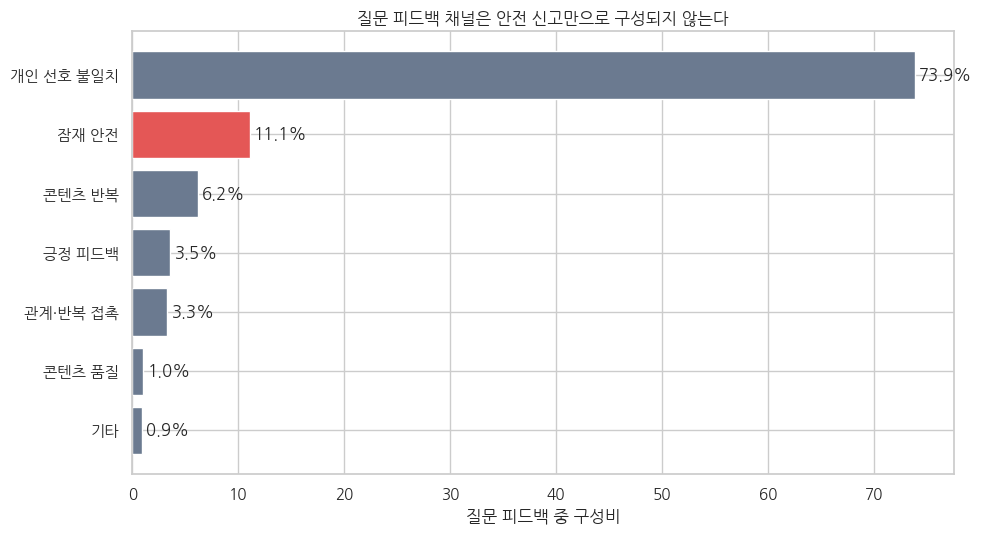

,label,events,share_pct
0,개인 선호 불일치,37987,73.8702
1,잠재 안전,5694,11.0727
2,콘텐츠 반복,3202,6.2267
3,긍정 피드백,1821,3.5411
4,관계·반복 접촉,1701,3.3078
5,콘텐츠 품질,539,1.0481
6,기타,480,0.9334


In [ ]:
# 질문 피드백 사유 구성
td_domain_order = ['PERSONAL_PREFERENCE', 'CONTENT_SAFETY', 'CONTENT_REPETITION', 'POSITIVE_FEEDBACK', 'RELATIONSHIP_FREQUENCY', 'CONTENT_QUALITY', 'OTHER']
td_domain_ko = {'PERSONAL_PREFERENCE': '개인 선호 불일치', 'CONTENT_SAFETY': '잠재 안전', 'CONTENT_REPETITION': '콘텐츠 반복', 'POSITIVE_FEEDBACK': '긍정 피드백', 'RELATIONSHIP_FREQUENCY': '관계·반복 접촉', 'CONTENT_QUALITY': '콘텐츠 품질', 'OTHER': '기타'}
td_domain_counts = td_feedback['feedback_domain_rule_v1'].value_counts().reindex(td_domain_order).fillna(0).astype(int).rename_axis('domain').reset_index(name='events')
td_domain_counts['label'] = td_domain_counts['domain'].map(td_domain_ko)
td_domain_counts['share_pct'] = td_domain_counts['events'] / td_domain_counts['events'].sum() * 100
td_fig, td_ax = plt.subplots(figsize=(10, 5.5))
td_plot = td_domain_counts.sort_values('events')
td_colors = ['#E45756' if td_d == 'CONTENT_SAFETY' else '#6B7A90' for td_d in td_plot['domain']]
td_ax.barh(td_plot['label'], td_plot['share_pct'], color=td_colors)
for td_y, td_value in enumerate(td_plot['share_pct']):
    td_ax.text(td_value + 0.35, td_y, f'{td_value:.1f}%', va='center')
td_ax.set_xlabel('질문 피드백 중 구성비')
td_ax.set_ylabel('')
td_ax.set_title('질문 피드백 채널은 안전 신고만으로 구성되지 않는다')
td_savefig('02_feedback_domain_composition.png')
display(td_domain_counts[['label', 'events', 'share_pct']])
plt.close('all')
_t7tc_collected = gc.collect()


- 개인 선호 불일치가 73.9%로 대부분이고, 잠재 안전은 11.1%, 콘텐츠 반복은 6.2%다. 전체를 안전 신고로 부르면 선호와 반복 노출 문제가 묻히게 된다.


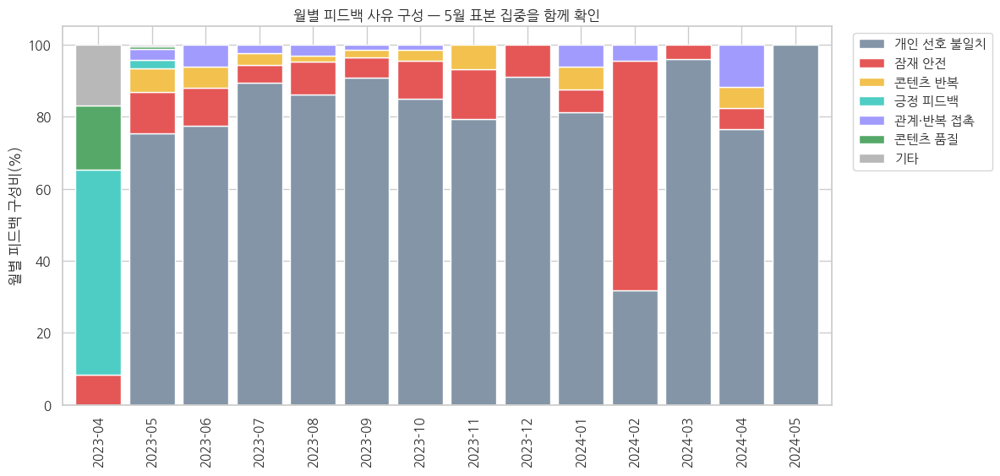

전체 질문 피드백 중 2023년 5월 비중: 86.2%


In [ ]:
# 월별 피드백 규모·구성
td_monthly = pd.crosstab(td_feedback['event_month'], td_feedback['feedback_domain_rule_v1'])
td_monthly = td_monthly.reindex(columns=td_domain_order, fill_value=0)
td_monthly_share = td_monthly.div(td_monthly.sum(axis=1), axis=0) * 100
td_monthly_out = td_monthly.reset_index().merge(td_monthly_share.reset_index(), on='event_month', suffixes=('_events', '_share_pct'))
td_fig, td_ax = plt.subplots(figsize=(12, 5.8))
td_palette = ['#8395A7', '#E45756', '#F2C14E', '#4ECDC4', '#A29BFE', '#55A868', '#B8B8B8']
td_monthly_share.rename(columns=td_domain_ko).plot(kind='bar', stacked=True, ax=td_ax, color=td_palette, width=0.85)
td_ax.set_ylabel('월별 피드백 구성비(%)')
td_ax.set_xlabel('')
td_ax.set_title('월별 피드백 사유 구성 — 5월 표본 집중을 함께 확인')
td_ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
td_savefig('03_monthly_feedback_composition.png')
td_may_share = (td_feedback['event_month'] == '2023-05').mean() * 100
print(f'전체 질문 피드백 중 2023년 5월 비중: {td_may_share:.1f}%')
plt.close('all')
_t7tc_collected = gc.collect()


- 질문 피드백의 86.2%가 2023년 5월에 집중됐다. 전체 기간과 5월 한정 결과를 구분해 비교했다.


In [ ]:
# 사용자·문구 중복 제거
td_linked = td_feedback.loc[td_feedback['normalized_text'].notna()].copy()
td_pair_raw = td_linked.groupby(['actor_user_id', 'normalized_text'], as_index=False).agg(label_min=('potential_safety', 'min'), label_max=('potential_safety', 'max'), raw_rows=('potential_safety', 'size'), first_event_at=('event_at', 'min'), question_text=('question_text', 'first'), question_id=('question_id', 'first'))
td_pair_raw['mixed_reason_pair'] = td_pair_raw['label_min'].ne(td_pair_raw['label_max'])
td_pair = td_pair_raw.loc[~td_pair_raw['mixed_reason_pair']].copy()
td_pair['potential_safety'] = td_pair['label_max'].astype(int)
td_pair['event_month'] = td_pair['first_event_at'].dt.to_period('M').astype(str)
td_repeat_qa = pd.DataFrame([('원시 연결 행', len(td_linked)), ('고유 actor × text', len(td_pair_raw)), ('반복으로 축약된 행', len(td_linked) - len(td_pair_raw)), ('동일 actor-text에 안전·비안전 사유가 모두 존재', td_pair_raw['mixed_reason_pair'].sum()), ('모델 주 분석의 순수 actor-text', len(td_pair)), ('주 분석 잠재 안전 actor-text', td_pair['potential_safety'].sum())], columns=['항목', '값'])
display(td_repeat_qa)
td_actor_concentration = td_linked.groupby('actor_user_id').size().sort_values(ascending=False)
print('사용자 1명당 질문 피드백 수 분위수')
display(td_actor_concentration.quantile([0, 0.5, 0.9, 0.95, 0.99, 1]).rename('feedback_rows').to_frame())
plt.close('all')
_t7tc_collected = gc.collect()


,항목,값
0,원시 연결 행,51415
1,고유 actor × text,44593
2,반복으로 축약된 행,6822
3,동일 actor-text에 안전·비안전 사유가 모두 존재,569
4,모델 주 분석의 순수 actor-text,44024
5,주 분석 잠재 안전 actor-text,4686


사용자 1명당 질문 피드백 수 분위수


,feedback_rows
0.0000,1.0000
0.5000,1.0000
0.9000,4.0000
0.9500,7.0000
0.9900,19.0000
1.0000,862.0000


- 동일 사용자·문구의 반복 행 6,822개를 축약하고, 안전·비안전 사유가 함께 있는 569쌍을 제외해 모델 표본 44,024쌍을 구성했다.


### 3-6-6. 문구별 신호와 의미군 분리

- 형태소·임베딩을 연결하고 의미군 단위로 학습·검증·테스트 표본을 나눴다.


In [ ]:
# Content 문구 특징 연결
td_content_assets = globals().get('team7_content_assets', {})
if 'text_features' in td_content_assets:
    td_text_features = td_content_assets['text_features'].copy()
else:
    td_text_features = pd.read_csv(td_TEXT_FEATURE_PATH)
td_text_features = td_text_features.rename(columns={'question_text_normalized': 'normalized_text'})
if 'theme_map' in td_content_assets:
    td_theme_map = td_content_assets['theme_map'].copy()
else:
    td_theme_map = pd.read_csv(td_TEXT_THEME_PATH, usecols=['question_text_normalized', 'refined_theme_id', 'theme_label_ko'])
td_theme_map = td_theme_map.drop_duplicates('question_text_normalized')
td_theme_map = td_theme_map.rename(columns={'question_text_normalized': 'normalized_text'})
td_text_features = td_text_features.merge(td_theme_map, on='normalized_text', how='left')
if 'texts' in td_content_assets and 'embeddings' in td_content_assets:
    td_embedding_texts = pd.Index(np.asarray(td_content_assets['texts'], dtype=str), name='normalized_text')
    td_embeddings = np.asarray(td_content_assets['embeddings'], dtype='float32')
else:
    with np.load(td_EMBEDDING_PATH, allow_pickle=True) as td_emb_npz:
        td_embedding_texts = pd.Index(td_emb_npz['texts'].astype(str), name='normalized_text')
        td_embeddings = td_emb_npz['embeddings'].astype('float32')
if len(td_embedding_texts) != len(td_embeddings) or not td_embedding_texts.is_unique:
    raise ValueError('Content 임베딩과 문구 목록의 행 수·중복을 확인해야 합니다.')
td_embedding_index = pd.Series(np.arange(len(td_embedding_texts)), index=td_embedding_texts)
td_pair = td_pair.merge(td_text_features[['normalized_text', 'token_text', 'semantic_group_090', 'umap_x', 'umap_y', 'piece_count', 'theme_label_ko', 'refined_theme_id']], on='normalized_text', how='left', validate='many_to_one')
td_missing_group = td_pair['semantic_group_090'].isna()
# 특징 미연결 행마다 별도 의미군 ID 부여
td_pair.loc[td_missing_group, 'semantic_group_090'] = np.arange(td_missing_group.sum()) + 10000000
td_pair['semantic_group_090'] = td_pair['semantic_group_090'].astype(int)
td_pair['token_text'] = td_pair['token_text'].fillna(td_pair['normalized_text'])
td_asset_qa = pd.DataFrame([('주 분석 actor-text', len(td_pair)), ('주 분석 고유 문구', td_pair['normalized_text'].nunique()), ('특징 미연결 행·행별 의미군 부여', int(td_missing_group.sum())), ('특징 미연결 고유 문구', td_pair.loc[td_missing_group, 'normalized_text'].nunique()), ('토큰·대체 문구 입력', td_pair['token_text'].notna().sum()), ('SBERT 임베딩 연결', td_pair['normalized_text'].isin(td_embedding_index.index).sum()), ('semantic family 연결', td_pair['semantic_group_090'].notna().sum()), ('탐색용 의미 테마 연결', td_pair['refined_theme_id'].notna().sum())], columns=['항목', '값'])
display(td_asset_qa)
plt.close('all')
_t7tc_collected = gc.collect()


,항목,값
0,주 분석 actor-text,44024
1,주 분석 고유 문구,2963
2,특징 미연결 행·행별 의미군 부여,7
3,특징 미연결 고유 문구,2
4,토큰·대체 문구 입력,44024
5,SBERT 임베딩 연결,44017
6,semantic family 연결,44024
7,탐색용 의미 테마 연결,44017


- 주 분석 표본은 사용자·문구 44,024쌍, 고유 문구 2,963개다. 특징이 연결되지 않은 두 문구의 7행에는 행별 의미군을 부여했다.
- 미연결 행은 정규화 문구와 0벡터를 사용한다. 동일 문구가 여러 분할에 포함될 수 있어 문구 중복을 별도로 확인했다.


In [ ]:
# 의미군 단위 학습·검증·평가 분할
td_sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=td_SEED)
td_pair['fold'] = -1
for td_fold, (td__, td_idx) in enumerate(td_sgkf.split(td_pair['normalized_text'], td_pair['potential_safety'], groups=td_pair['semantic_group_090'])):
    td_pair.iloc[td_idx, td_pair.columns.get_loc('fold')] = td_fold
td_pair['split'] = np.select([td_pair['fold'].eq(0), td_pair['fold'].eq(1)], ['test', 'validation'], default='train')
td_split_qa = td_pair.groupby('split').agg(rows=('potential_safety', 'size'), safety=('potential_safety', 'sum'), texts=('normalized_text', 'nunique'), semantic_families=('semantic_group_090', 'nunique')).assign(safety_share=lambda td_d: td_d['safety'] / td_d['rows']).reset_index()
display(td_split_qa)
assert td_pair.groupby('semantic_group_090')['split'].nunique().max() == 1
# 의미군별 분할 후 정규화 문구의 중복 여부를 점검한다.
print('정규화 문구별 최대 분할 수:', td_pair.groupby('normalized_text')['split'].nunique().max())
plt.close('all')
_t7tc_collected = gc.collect()


,split,rows,safety,texts,semantic_families,safety_share
0,test,8148,940,586,555,0.1154
1,train,26271,2700,1796,1668,0.1028
2,validation,9605,1046,583,554,0.1089


정규화 문구별 최대 분할 수: 3


- 학습 26,271쌍, 검증 9,605쌍, 테스트 8,148쌍으로 나뉘었으며, 잠재 안전 비중은 각각 10.28%·10.89%·11.54%다.
- 의미군은 분할 사이에 겹치지 않지만, 미연결 문구의 행별 의미군 처리로 같은 정규화 문구가 최대 3개 분할에 포함됐다. 완전히 새로운 문구만으로 평가한 결과는 아니다.


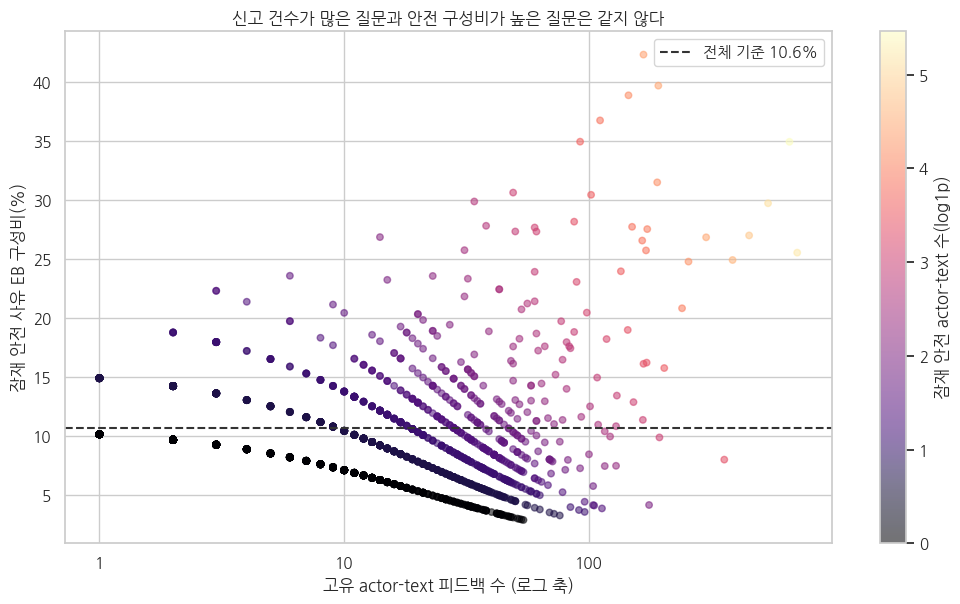

잠재 안전 건수 상위 문구


,question_text,feedback_pairs,safety_pairs,eb_safety_share
1225,발냄새가 호두과자 냄새일 것 같은 사람은?,659,235,0.3492
976,마스크가 잘 어울리는 사람은?,709,184,0.2553
913,등빨이 가장 좋은 사람은?,539,164,0.2972
1788,어깨가 가장 넓은 사람은?,451,125,0.2699
1079,먹방을 가장 잘할 것 같은 사람은?,386,99,0.2491
1516,설레면 콧구멍이 커지는 친구는?,301,84,0.2683
2112,이모티콘만 보고 알아서 상상해서 골라봐,192,82,0.3968
137,가장 매력적인 사람은?,167,77,0.4231
1224,발냄새가 가장 향긋할 것 같은 사람은?,255,66,0.2477
2492,첫 키스를 가장 먼저 해봤을 것 같은 사람은?,190,64,0.3149


피드백 10건 이상 중 안전 구성비 하한이 높은 문구


,question_text,feedback_pairs,safety_pairs,eb_safety_share,eb_ci_low
137,가장 매력적인 사람은?,167,77,0.4231,0.3534
2112,이모티콘만 보고 알아서 상상해서 골라봐,192,82,0.3968,0.3321
924,땀냄새가 가장 좋을 것 같은 사람은?,145,62,0.3887,0.3159
1225,발냄새가 호두과자 냄새일 것 같은 사람은?,659,235,0.3492,0.3138
2747,플러팅을 제일 잘하는 사람은?,111,46,0.3674,0.2872
2263,전남친/여친 SNS 염탐할 것 같은 사람은?,92,37,0.3494,0.2642
913,등빨이 가장 좋은 사람은?,539,164,0.2972,0.2600
2492,첫 키스를 가장 먼저 해봤을 것 같은 사람은?,190,64,0.3149,0.2540
1788,어깨가 가장 넓은 사람은?,451,125,0.2699,0.2308
971,마사지 해줬으면 좋겠는 사람은?,102,35,0.3043,0.2262


In [ ]:
# 문구별 잠재 안전 구성비
td_text_stats = td_pair.groupby('normalized_text', as_index=False).agg(question_text=('question_text', 'first'), feedback_pairs=('potential_safety', 'size'), safety_pairs=('potential_safety', 'sum'), reporters=('actor_user_id', 'nunique'), piece_count=('piece_count', 'first'), theme_label_ko=('theme_label_ko', 'first'), refined_theme_id=('refined_theme_id', 'first'), semantic_group_090=('semantic_group_090', 'first'), umap_x=('umap_x', 'first'), umap_y=('umap_y', 'first'))
td_p0 = td_pair['potential_safety'].mean()
td_prior_strength = 20
td_alpha0, td_beta0 = (td_p0 * td_prior_strength, (1 - td_p0) * td_prior_strength)
td_text_stats['raw_safety_share'] = td_text_stats['safety_pairs'] / td_text_stats['feedback_pairs']
td_text_stats['eb_safety_share'] = (td_text_stats['safety_pairs'] + td_alpha0) / (td_text_stats['feedback_pairs'] + td_prior_strength)
td_text_stats['eb_ci_low'] = scipy_stats.beta.ppf(0.025, td_text_stats['safety_pairs'] + td_alpha0, td_text_stats['feedback_pairs'] - td_text_stats['safety_pairs'] + td_beta0)
td_text_stats['eb_ci_high'] = scipy_stats.beta.ppf(0.975, td_text_stats['safety_pairs'] + td_alpha0, td_text_stats['feedback_pairs'] - td_text_stats['safety_pairs'] + td_beta0)
td_text_stats['high_confidence_above_global'] = td_text_stats['eb_ci_low'] > td_p0
td_top_volume = td_text_stats.sort_values(['safety_pairs', 'feedback_pairs'], ascending=False).head(15)
td_top_composition = td_text_stats.loc[td_text_stats['feedback_pairs'].ge(10)].sort_values('eb_ci_low', ascending=False).head(15)
td_fig, td_ax = plt.subplots(figsize=(10.5, 6.2))
td_sc = td_ax.scatter(td_text_stats['feedback_pairs'], td_text_stats['eb_safety_share'] * 100, c=np.log1p(td_text_stats['safety_pairs']), cmap='magma', alpha=0.55, s=22)
td_ax.set_xscale('log')
td_ax.xaxis.set_major_formatter(lambda td_value, td_position: f'{td_value:g}')
td_ax.xaxis.set_minor_formatter(lambda td_value, td_position: '')
td_ax.axhline(td_p0 * 100, color='#333333', linestyle='--', label=f'전체 기준 {td_p0 * 100:.1f}%')
td_ax.set_xlabel('고유 actor-text 피드백 수 (로그 축)')
td_ax.set_ylabel('잠재 안전 사유 EB 구성비(%)')
td_ax.set_title('신고 건수가 많은 질문과 안전 구성비가 높은 질문은 같지 않다')
td_ax.legend()
plt.colorbar(td_sc, ax=td_ax, label='잠재 안전 actor-text 수(log1p)')
td_savefig('07_question_volume_vs_safety_composition.png')
print('잠재 안전 건수 상위 문구')
display(td_top_volume[['question_text', 'feedback_pairs', 'safety_pairs', 'eb_safety_share']].head(10))
print('피드백 10건 이상 중 안전 구성비 하한이 높은 문구')
display(td_top_composition[['question_text', 'feedback_pairs', 'safety_pairs', 'eb_safety_share', 'eb_ci_low']].head(10))
plt.close('all')
_t7tc_collected = gc.collect()


- 문구별 피드백 비율과 소표본 보정 비율을 함께 확인했다.
- 분모는 해당 문구의 피드백이며, 실제 노출자 중 위해를 겪은 비율이 아니다.


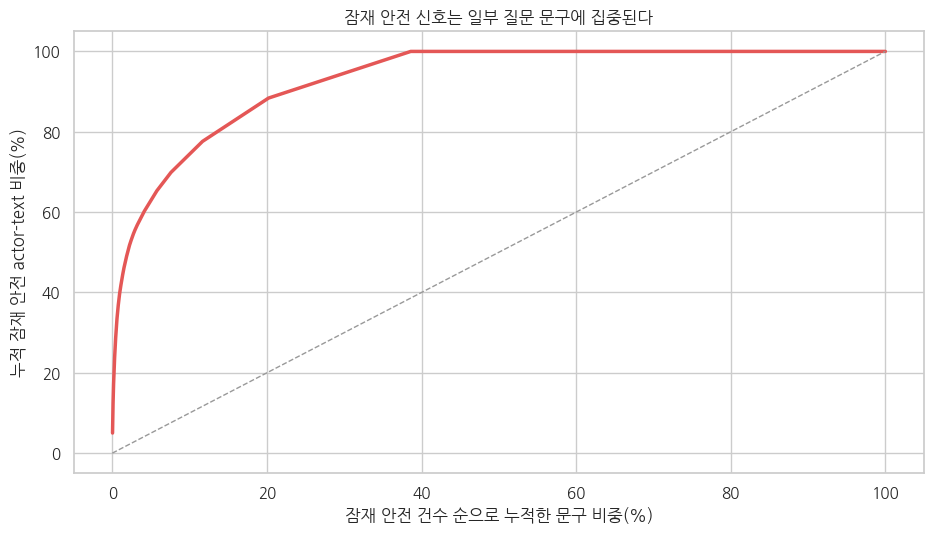

상위 1% 문구가 잠재 안전 actor-text의 40.1%를 포함
상위 5% 문구가 잠재 안전 actor-text의 62.9%를 포함
상위 10% 문구가 잠재 안전 actor-text의 74.4%를 포함


In [ ]:
# 잠재 안전 신호 집중도
td_safety_sorted = td_text_stats.sort_values('safety_pairs', ascending=False).reset_index(drop=True)
td_safety_sorted['text_rank'] = np.arange(1, len(td_safety_sorted) + 1)
td_safety_sorted['text_share'] = td_safety_sorted['text_rank'] / len(td_safety_sorted)
td_safety_sorted['cumulative_safety_share'] = td_safety_sorted['safety_pairs'].cumsum() / td_safety_sorted['safety_pairs'].sum()
td_fig, td_ax = plt.subplots(figsize=(9.5, 5.5))
td_ax.plot(td_safety_sorted['text_share'] * 100, td_safety_sorted['cumulative_safety_share'] * 100, color='#E45756', linewidth=2.5)
td_ax.plot([0, 100], [0, 100], color='#999999', linestyle='--', linewidth=1)
td_ax.set_xlabel('잠재 안전 건수 순으로 누적한 문구 비중(%)')
td_ax.set_ylabel('누적 잠재 안전 actor-text 비중(%)')
td_ax.set_title('잠재 안전 신호는 일부 질문 문구에 집중된다')
td_savefig('08_safety_signal_pareto.png')
for td_pct in [1, 5, 10]:
    td_k = max(1, int(len(td_safety_sorted) * td_pct / 100))
    td_captured = td_safety_sorted.head(td_k)['safety_pairs'].sum() / td_safety_sorted['safety_pairs'].sum() * 100
    print(f'상위 {td_pct}% 문구가 잠재 안전 actor-text의 {td_captured:.1f}%를 포함')
plt.close('all')
_t7tc_collected = gc.collect()


- 상위 1% 문구에 사용자·문구 기준 잠재 안전 신호의 40.1%가 모이고, 상위 5%에는 62.9%가 모인다. 검토할 문구의 우선순위를 좁힐 여지가 크다. 공급량이 많은 문구의 영향은 여전히 포함돼 있다.


### 3-6-7. 표현 범주와 잠재 안전 사유

- 표현 범주별 피드백 구성, 월·문장 길이를 고려한 모형, 유사 문구 쌍을 비교했다.
- 후보자·친구 관계 맥락은 포함하지 않아 표현의 인과효과로 해석하지 않는다.


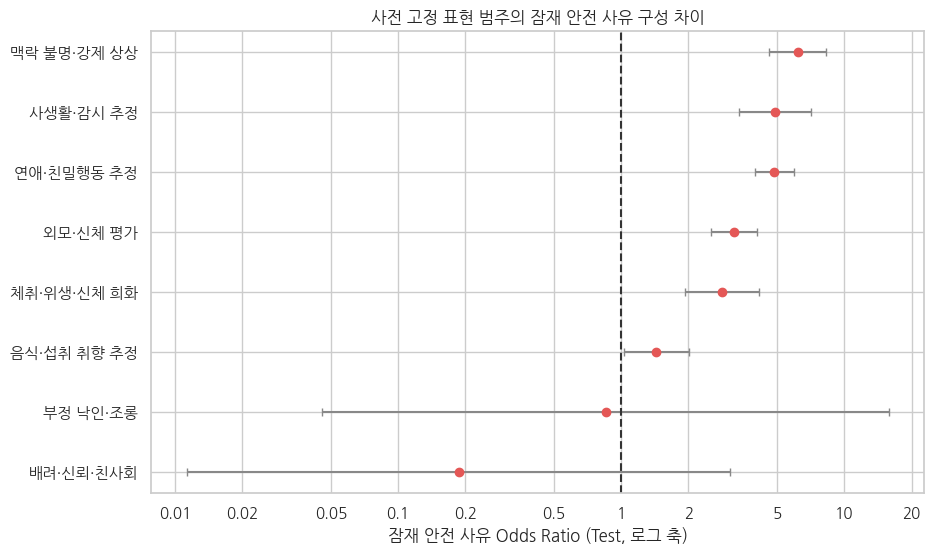

,category,rows_with_flag,safety_share_with,safety_share_without,delta_pp,odds_ratio,or_ci_low,or_ci_high,q_value
15,배려·신뢰·친사회,20,0.0000,0.1156,-11.5650,0.1864,0.0113,3.0849,0.1804
9,부정 낙인·조롱,4,0.0000,0.1154,-11.5422,0.8511,0.0458,15.8221,1.0000
13,음식·섭취 취향 추정,272,0.1544,0.1140,4.0394,1.4321,1.0249,2.0009,0.0703
3,체취·위생·신체 희화,141,0.2624,0.1128,14.9635,2.8218,1.9307,4.1240,0.0000
7,외모·신체 평가,371,0.2776,0.1076,17.0003,3.1945,2.5183,4.0522,0.0000
5,연애·친밀행동 추정,484,0.3512,0.1005,25.0770,4.8510,3.9688,5.9293,0.0000
1,사생활·감시 추정,124,0.3790,0.1113,26.7741,4.8919,3.3864,7.0667,0.0000
11,맥락 불명·강제 상상,192,0.4271,0.1078,31.9240,6.1733,4.6015,8.2820,0.0000


In [ ]:
# 표현 사전·잠재 안전 연관
td_LEXICON = {'사생활·감시 추정': ['염탐', '몰폰', '스토킹', '몰래 보', '몰래볼', 'sns 훔쳐', '비밀을 볼'], '체취·위생·신체 희화': ['발냄새', '땀냄새', '냄새', '방귀', '발가락', '콧구멍', '겨드랑이', '코딱지', '콧물', '백태', '트름', '더럽', '씻지', '목욕 안'], '연애·친밀행동 추정': ['키스', '스킨십', '성관계', '야한', '19금', '모텔', '첫경험', '남친', '여친', '전남친', '전여친', '플러팅', '양다리', '사귀', '호감', '신체접촉'], '외모·신체 평가': ['몸매', '외모', '얼굴', '어깨', '등빨', '가슴', '뚱뚱', '살찐', '못생', '마스크', '섹시', '근육', '피부', '매력적인', '화장'], '부정 낙인·조롱': ['찐따', '아싸', '바보', '멍청', '관종', '허당', '재수없', '눈치없', '민폐', '최악', '왕따', '일진', '폭력', '범죄', '중독'], '맥락 불명·강제 상상': ['이모티콘만 보고', '알아서 상상', '상상해서 골라', 'vote'], '음식·섭취 취향 추정': ['먹방', '토스트', '와플', '탕후루', '음식을', '먹을 것', '먹는 사람'], '배려·신뢰·친사회': ['배려', '믿음', '믿을', '챙김', '챙겨', '고민을', '위로', '의리', '친절']}
td_CORE_RISK_CATEGORIES = ['사생활·감시 추정', '체취·위생·신체 희화', '연애·친밀행동 추정', '외모·신체 평가']

def td_lexicon_flag(td_text, td_words):
    return int(any((td_word in str(td_text) for td_word in td_words)))
for td_category, td_words in td_LEXICON.items():
    td_pair[f'lex_{td_category}'] = td_pair['normalized_text'].map(lambda td_x: td_lexicon_flag(td_x, td_words))
    td_text_stats[f'lex_{td_category}'] = td_text_stats['normalized_text'].map(lambda td_x: td_lexicon_flag(td_x, td_words))
td_lex_cols = [f'lex_{td_c}' for td_c in td_LEXICON]
td_core_cols = [f'lex_{td_c}' for td_c in td_CORE_RISK_CATEGORIES]
td_pair['lex_any'] = td_pair[td_core_cols].max(axis=1)
td_text_stats['lex_any'] = td_text_stats[td_core_cols].max(axis=1)
td_lex_rows = []
for td_category in td_LEXICON:
    td_col = f'lex_{td_category}'
    for td_split_name in ['all', 'test']:
        td_sub = td_pair if td_split_name == 'all' else td_pair.loc[td_pair['split'].eq('test')]
        td_present = td_sub[td_col].eq(1)
        td_a = int(td_sub.loc[td_present, 'potential_safety'].sum())
        td_b = int(td_present.sum() - td_a)
        td_c = int(td_sub.loc[~td_present, 'potential_safety'].sum())
        td_d = int((~td_present).sum() - td_c)
        td_odds_ratio, td_pvalue = fisher_exact([[td_a, td_b], [td_c, td_d]]) if td_a + td_b > 0 else (np.nan, np.nan)
        td_rate_present = td_a / (td_a + td_b) if td_a + td_b else np.nan
        td_rate_absent = td_c / (td_c + td_d) if td_c + td_d else np.nan
        td_se = math.sqrt(sum((1 / (td_v + 0.5) for td_v in [td_a, td_b, td_c, td_d]))) if td_a + td_b > 0 else np.nan
        td_log_or = math.log((td_a + 0.5) * (td_d + 0.5) / ((td_b + 0.5) * (td_c + 0.5))) if td_a + td_b > 0 else np.nan
        td_lex_rows.append({'split': td_split_name, 'category': td_category, 'rows_with_flag': td_a + td_b, 'safety_share_with': td_rate_present, 'safety_share_without': td_rate_absent, 'delta_pp': (td_rate_present - td_rate_absent) * 100, 'odds_ratio': math.exp(td_log_or), 'or_ci_low': math.exp(td_log_or - 1.96 * td_se), 'or_ci_high': math.exp(td_log_or + 1.96 * td_se), 'p_value': td_pvalue})
td_lexicon_results = pd.DataFrame(td_lex_rows)
td_lexicon_results['q_value'] = td_lexicon_results.groupby('split')['p_value'].transform(td_bh_adjust)
td_test_lex = td_lexicon_results.loc[td_lexicon_results['split'].eq('test')].sort_values('odds_ratio')
td_test_lex_plot = td_test_lex.dropna(subset=['odds_ratio', 'or_ci_low', 'or_ci_high'])
td_fig, td_ax = plt.subplots(figsize=(9.5, 5.7))
td_y = np.arange(len(td_test_lex_plot))
td_ax.errorbar(td_test_lex_plot['odds_ratio'], td_y, xerr=[td_test_lex_plot['odds_ratio'] - td_test_lex_plot['or_ci_low'], td_test_lex_plot['or_ci_high'] - td_test_lex_plot['odds_ratio']], fmt='o', color='#E45756', ecolor='#888888', capsize=3)
td_ax.axvline(1, color='#333333', linestyle='--')
td_ax.set_yticks(td_y, td_test_lex_plot['category'])
td_ax.set_xscale('log')
td_ax.set_xticks([td_tick for td_tick in (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100) if td_ax.get_xlim()[0] <= td_tick <= td_ax.get_xlim()[1]])
td_ax.xaxis.set_major_formatter(lambda td_value, td_position: f'{td_value:g}')
td_ax.xaxis.set_minor_formatter(lambda td_value, td_position: '')
td_ax.set_xlabel('잠재 안전 사유 Odds Ratio (Test, 로그 축)')
td_ax.set_title('사전 고정 표현 범주의 잠재 안전 사유 구성 차이')
td_savefig('09_seed_lexicon_test_effects.png')
display(td_test_lex[['category', 'rows_with_flag', 'safety_share_with', 'safety_share_without', 'delta_pp', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value']])
plt.close('all')
_t7tc_collected = gc.collect()


- 테스트 표본에서 사생활·감시 표현의 잠재 안전 비중은 표현 있음 37.9%·없음 11.1%, 외모·신체 평가는 27.8%·10.8%다.
- 맥락 불명·강제 상상은 192쌍이며 잠재 안전 비중은 42.7%다. 고정된 테스트 표본의 관측 연관이지 표현의 인과효과가 아니다.


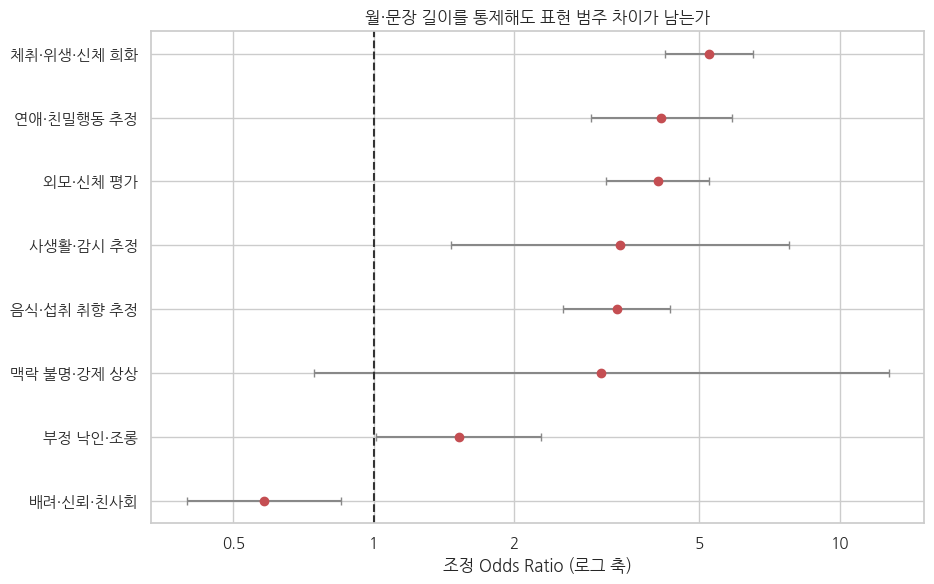

,category,adjusted_odds_ratio,or_ci_low,or_ci_high,p_value,q_value
1,체취·위생·신체 희화,5.2462,4.2134,6.5321,0.0000,0.0000
2,연애·친밀행동 추정,4.1414,2.9215,5.8708,0.0000,0.0000
3,외모·신체 평가,4.0667,3.1490,5.2519,0.0000,0.0000
0,사생활·감시 추정,3.3769,1.4663,7.7770,0.0042,0.0068
6,음식·섭취 취향 추정,3.3258,2.5532,4.3323,0.0000,0.0000
5,맥락 불명·강제 상상,3.0794,0.7435,12.7542,0.1208,0.1208
4,부정 낙인·조롱,1.5227,1.0116,2.2920,0.0439,0.0501
7,배려·신뢰·친사회,0.5811,0.3968,0.8509,0.0053,0.0070


In [ ]:
# 다른 조건을 고려한 표현 범주 비교
td_glm_data = td_pair.copy()
td_glm_data['text_length_z'] = (td_glm_data['normalized_text'].str.len() - td_glm_data['normalized_text'].str.len().mean()) / td_glm_data['normalized_text'].str.len().std()
td_month_dummies = pd.get_dummies(td_glm_data['event_month'], prefix='month', drop_first=True, dtype=float)
td_X_glm = pd.concat([td_glm_data[td_lex_cols].astype(float), td_glm_data[['text_length_z']], td_month_dummies], axis=1)
td_X_glm = td_sm.add_constant(td_X_glm, has_constant='add')
td_glm_fit = td_sm.GLM(td_glm_data['potential_safety'].astype(float), td_X_glm, family=td_sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': td_glm_data['semantic_group_090']})
td_glm_rows = []
for td_category in td_LEXICON:
    td_term = f'lex_{td_category}'
    td_coef, td_se, td_pvalue = (td_glm_fit.params[td_term], td_glm_fit.bse[td_term], td_glm_fit.pvalues[td_term])
    td_glm_rows.append({'category': td_category, 'adjusted_odds_ratio': math.exp(td_coef), 'or_ci_low': math.exp(td_coef - 1.96 * td_se), 'or_ci_high': math.exp(td_coef + 1.96 * td_se), 'p_value': td_pvalue})
td_glm_effects = pd.DataFrame(td_glm_rows)
td_glm_effects['q_value'] = td_bh_adjust(td_glm_effects['p_value'])
td_plot = td_glm_effects.sort_values('adjusted_odds_ratio')
td_fig, td_ax = plt.subplots(figsize=(9.5, 6))
td_y = np.arange(len(td_plot))
td_ax.errorbar(td_plot['adjusted_odds_ratio'], td_y, xerr=[td_plot['adjusted_odds_ratio'] - td_plot['or_ci_low'], td_plot['or_ci_high'] - td_plot['adjusted_odds_ratio']], fmt='o', color='#C44E52', ecolor='#888888', capsize=3)
td_ax.axvline(1, color='#333333', linestyle='--')
td_ax.set_yticks(td_y, td_plot['category'])
td_ax.set_xscale('log')
td_ax.set_xticks([td_tick for td_tick in (0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100) if td_ax.get_xlim()[0] <= td_tick <= td_ax.get_xlim()[1]])
td_ax.xaxis.set_major_formatter(lambda td_value, td_position: f'{td_value:g}')
td_ax.xaxis.set_minor_formatter(lambda td_value, td_position: '')
td_ax.set_xlabel('조정 Odds Ratio (로그 축)')
td_ax.set_title('월·문장 길이를 통제해도 표현 범주 차이가 남는가')
td_savefig('10_adjusted_lexicon_glm.png')
display(td_glm_effects.sort_values('adjusted_odds_ratio', ascending=False))
plt.close('all')
_t7tc_collected = gc.collect()


- 월과 문장 길이를 고려해도 체취·위생 희화, 연애·친밀행동 추정, 외모·신체 평가의 조정 오즈비가 높게 남았다. 각각 약 5.25, 4.14, 4.07이다.

- 같은 시기와 비슷한 길이 안에서도 표현 범주와 피드백 사유가 함께 달라졌다는 결과다.


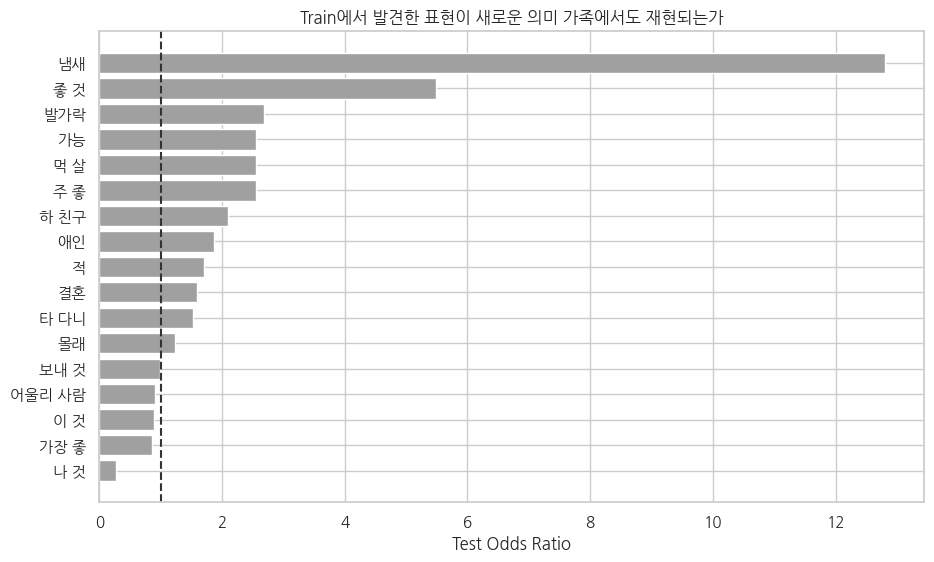

Train 후보 30개 중 Test 재현 기준 충족: 0개
GitHub 원본의 0.5 보정 계산을 유지했다. 표본이 없는 어휘의 수치는 관측 효과로 해석하지 않는다.


,term,unique_texts_with,rows_with,safety_share_with,delta_pp,odds_ratio,or_ci_low,or_ci_high,q_value_selected,replicated
376,냄새,1,3.0000,0.6667,55.1504,12.7997,1.6888,97.0127,0.2043,False
201,결혼 하,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
244,과자,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
298,길 것,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
434,누르,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
677,만약,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
867,발,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
1047,살 것,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
1104,성,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False
1206,실수,0,0.0000,0.0000,-11.5366,7.6645,0.1520,386.5238,0.4821,False


In [ ]:
# 새 어휘 후보의 재현 여부
def td_term_enrichment(td_frame, td_vectorizer=None, td_fit=False):
    if td_fit:
        td_vectorizer = CountVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, ngram_range=(1, 2), binary=True, min_df=20, max_features=20000)
        td_X = td_vectorizer.fit_transform(td_frame['token_text'].fillna(''))
    else:
        td_X = td_vectorizer.transform(td_frame['token_text'].fillna(''))
    td_terms = np.asarray(td_vectorizer.get_feature_names_out())
    td_y = td_frame['potential_safety'].to_numpy(dtype=int)
    td_pos = td_y == 1
    td_neg = ~td_pos
    td_a = np.asarray(td_X[td_pos].sum(axis=0)).ravel().astype(float)
    td_c = np.asarray(td_X[td_neg].sum(axis=0)).ravel().astype(float)
    td_b = td_pos.sum() - td_a
    td_d = td_neg.sum() - td_c
    td_log_or = np.log((td_a + 0.5) * (td_d + 0.5) / ((td_b + 0.5) * (td_c + 0.5)))
    td_se = np.sqrt(1 / (td_a + 0.5) + 1 / (td_b + 0.5) + 1 / (td_c + 0.5) + 1 / (td_d + 0.5))
    td_z = td_log_or / td_se
    td_p = 2 * scipy_stats.norm.sf(np.abs(td_z))
    td_rate_with = td_a / np.maximum(td_a + td_c, 1)
    td_rate_without = td_b / np.maximum(td_b + td_d, 1)
    td_stats = pd.DataFrame({'term': td_terms, 'safety_with': td_a, 'other_with': td_c, 'rows_with': td_a + td_c, 'safety_share_with': td_rate_with, 'safety_share_without': td_rate_without, 'delta_pp': (td_rate_with - td_rate_without) * 100, 'odds_ratio': np.exp(td_log_or), 'or_ci_low': np.exp(td_log_or - 1.96 * td_se), 'or_ci_high': np.exp(td_log_or + 1.96 * td_se), 'p_value': td_p})
    td_stats['q_value'] = td_bh_adjust(td_stats['p_value'])
    td_unique_text = td_frame.drop_duplicates('normalized_text')
    td_Xu = td_vectorizer.transform(td_unique_text['token_text'].fillna(''))
    td_stats['unique_texts_with'] = np.asarray(td_Xu.sum(axis=0)).ravel()
    return (td_stats, td_vectorizer)
td_train = td_pair.loc[td_pair['split'].eq('train')].copy()
td_validation = td_pair.loc[td_pair['split'].eq('validation')].copy()
td_test = td_pair.loc[td_pair['split'].eq('test')].copy()
td_train_terms, td_term_vectorizer = td_term_enrichment(td_train, td_fit=True)
td_candidate_terms = td_train_terms.loc[td_train_terms['unique_texts_with'].ge(3) & td_train_terms['q_value'].lt(0.05) & td_train_terms['odds_ratio'].ge(1.3) & td_train_terms['delta_pp'].ge(1.0)].sort_values(['delta_pp', 'odds_ratio'], ascending=False).head(30)['term'].tolist()
td_test_terms, td__ = td_term_enrichment(td_test, td_vectorizer=td_term_vectorizer, td_fit=False)
td_heldout_terms = td_test_terms.loc[td_test_terms['term'].isin(td_candidate_terms)].copy()
td_heldout_terms['q_value_selected'] = td_bh_adjust(td_heldout_terms['p_value'])
td_heldout_terms['replicated'] = td_heldout_terms['q_value_selected'].lt(0.05) & td_heldout_terms['odds_ratio'].ge(1.3) & td_heldout_terms['delta_pp'].gt(0) & td_heldout_terms['unique_texts_with'].ge(3)
td_heldout_terms = td_heldout_terms.sort_values(['replicated', 'odds_ratio'], ascending=False)
td_plot_terms = td_heldout_terms.loc[td_heldout_terms['rows_with'].gt(0)].head(18).sort_values('odds_ratio')
td_fig, td_ax = plt.subplots(figsize=(9.5, max(5.5, 0.34 * len(td_plot_terms))))
td_colors = np.where(td_plot_terms['replicated'], '#E45756', '#A0A0A0')
td_ax.barh(td_plot_terms['term'], td_plot_terms['odds_ratio'], color=td_colors)
td_ax.axvline(1, color='#333333', linestyle='--')
td_ax.set_xlabel('Test Odds Ratio')
td_ax.set_title('Train에서 발견한 표현이 새로운 의미 가족에서도 재현되는가')
td_savefig('11_heldout_token_replication.png')
print(f"Train 후보 {len(td_candidate_terms)}개 중 Test 재현 기준 충족: {int(td_heldout_terms['replicated'].sum())}개")
print('오즈비 계산에 0.5 보정을 사용한다. 표본이 없는 어휘의 수치는 관측 효과로 해석하지 않는다.')
display(td_heldout_terms[['term', 'unique_texts_with', 'rows_with', 'safety_share_with', 'delta_pp', 'odds_ratio', 'or_ci_low', 'or_ci_high', 'q_value_selected', 'replicated']].head(20))
plt.close('all')
_t7tc_collected = gc.collect()


- 학습에서 찾은 어휘 후보 30개 중 테스트 재현 기준을 통과한 어휘는 없었다.
- 0.5 보정으로 표본이 없는 어휘에도 오즈비가 계산될 수 있다. `rows_with`가 0인 수치는 관측 효과로 해석하지 않는다.


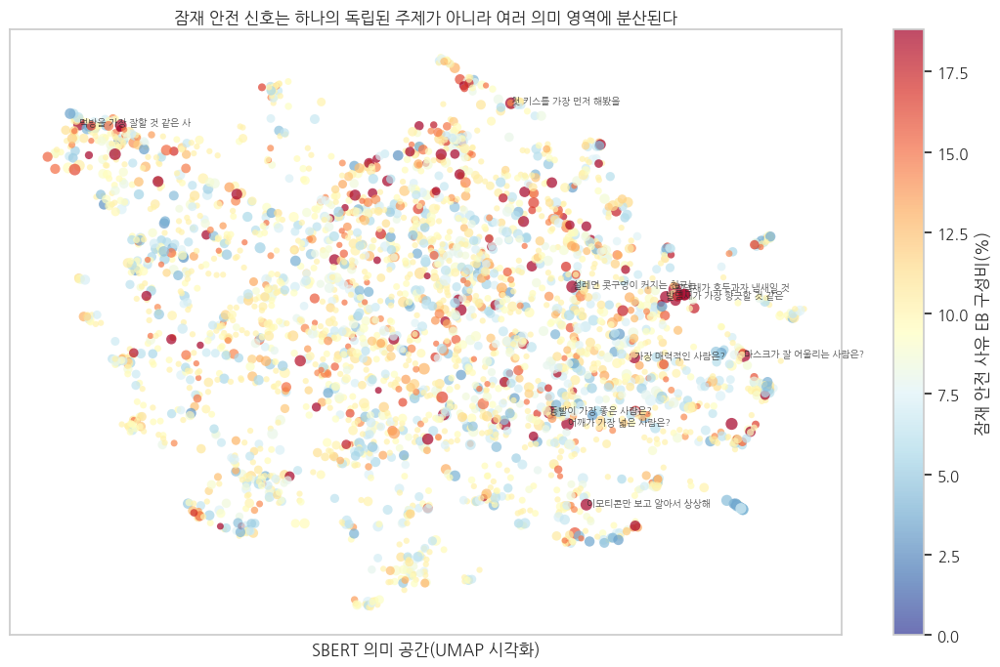

,refined_theme_id,theme_label_ko,feedback_pairs,safety_pairs,texts,safety_share,eb_safety_share
22,22.0000,향기·위생,1783,485,43,0.2720,0.2702
16,16.0000,버스·이동 상황,102,20,14,0.1961,0.1814
6,6.0000,능력·성숙·신뢰,3614,475,184,0.1314,0.1313
13,13.0000,연애·호감,3325,436,245,0.1311,0.1310
9,9.0000,매력·외모,6521,815,309,0.1250,0.1249
17,17.0000,음식·식사,3502,437,163,0.1248,0.1247
19,19.0000,결혼·가족·미래,1409,164,103,0.1164,0.1163
20,20.0000,두려움·부정 성향,1436,154,98,0.1072,0.1072
8,8.0000,인생·극한상황,487,51,54,0.1047,0.1048
12,12.0000,게임·운동·장난,2066,215,156,0.1041,0.1041


In [ ]:
# 의미 지도·테마별 피드백
td_semantic_plot = td_text_stats.dropna(subset=['umap_x', 'umap_y']).copy()
td_fig, td_ax = plt.subplots(figsize=(11, 7))
td_sc = td_ax.scatter(td_semantic_plot['umap_x'], td_semantic_plot['umap_y'], c=td_semantic_plot['eb_safety_share'] * 100, s=12 + np.log1p(td_semantic_plot['feedback_pairs']) * 12, cmap='RdYlBu_r', vmin=0, vmax=min(50, td_semantic_plot['eb_safety_share'].quantile(0.98) * 100), alpha=0.7, linewidth=0)
td_top_annotate = td_semantic_plot.nlargest(10, 'safety_pairs')
for td__, td_row in td_top_annotate.iterrows():
    td_ax.annotate(str(td_row['question_text'])[:16], (td_row['umap_x'], td_row['umap_y']), fontsize=7, alpha=0.8)
td_ax.set_xticks([])
td_ax.set_yticks([])
td_ax.set_xlabel('SBERT 의미 공간(UMAP 시각화)')
td_ax.set_title('잠재 안전 신호는 하나의 독립된 주제가 아니라 여러 의미 영역에 분산된다')
plt.colorbar(td_sc, ax=td_ax, label='잠재 안전 사유 EB 구성비(%)')
td_savefig('12_semantic_map_safety_composition.png')
td_theme_safety = td_pair.dropna(subset=['theme_label_ko']).groupby(['refined_theme_id', 'theme_label_ko'], as_index=False).agg(feedback_pairs=('potential_safety', 'size'), safety_pairs=('potential_safety', 'sum'), texts=('normalized_text', 'nunique'))
td_theme_safety['safety_share'] = td_theme_safety['safety_pairs'] / td_theme_safety['feedback_pairs']
td_theme_safety['eb_safety_share'] = (td_theme_safety['safety_pairs'] + td_alpha0) / (td_theme_safety['feedback_pairs'] + td_prior_strength)
display(td_theme_safety.sort_values('eb_safety_share', ascending=False).head(10))
plt.close('all')
_t7tc_collected = gc.collect()


- 의미 지도에서는 연애·호감, 향기·위생 등 가까운 질문들을 한곳에서 볼 수 있다. 잠재 안전 피드백이 많은 점의 문구를 찾아 읽는 탐색 자료로 썼다. 점 사이 거리를 위험 수준의 간격으로 읽을 수는 없다.


In [ ]:
# 비슷한 문구 쌍 비교
td_match_pool = td_text_stats.loc[td_text_stats['feedback_pairs'].ge(5)].copy()
td_match_pool['emb_idx'] = td_match_pool['normalized_text'].map(td_embedding_index)
td_match_pool = td_match_pool.dropna(subset=['emb_idx', 'refined_theme_id']).copy()
td_match_pool['emb_idx'] = td_match_pool['emb_idx'].astype(int)
td_risk_pool = td_match_pool.loc[td_match_pool['lex_any'].eq(1)].copy()
td_control_pool = td_match_pool.loc[td_match_pool['lex_any'].eq(0)].copy()
td_pairs = []
for td_theme_id, td_risk_group in td_risk_pool.groupby('refined_theme_id'):
    td_controls = td_control_pool.loc[td_control_pool['refined_theme_id'].eq(td_theme_id)].copy()
    if td_controls.empty:
        continue
    td_C = td_embeddings[td_controls['emb_idx'].to_numpy()]
    td_C = td_C / np.maximum(np.linalg.norm(td_C, axis=1, keepdims=True), 1e-12)
    td_R = td_embeddings[td_risk_group['emb_idx'].to_numpy()]
    td_R = td_R / np.maximum(np.linalg.norm(td_R, axis=1, keepdims=True), 1e-12)
    td_sims = td_R @ td_C.T
    for td_i, (td__, td_rr) in enumerate(td_risk_group.iterrows()):
        td_order = np.argsort(-td_sims[td_i])
        td_chosen = None
        for td_j in td_order[:20]:
            td_cc = td_controls.iloc[td_j]
            if abs(len(td_rr['normalized_text']) - len(td_cc['normalized_text'])) > 18:
                continue
            if abs(np.log1p(td_rr['feedback_pairs']) - np.log1p(td_cc['feedback_pairs'])) > 1.5:
                continue
            if td_sims[td_i, td_j] < 0.6:
                continue
            td_chosen = td_cc
            break
        if td_chosen is not None:
            td_pairs.append({'risk_text': td_rr['question_text'], 'control_text': td_chosen['question_text'], 'cosine': float(td_sims[td_i, td_controls.index.get_loc(td_chosen.name)]), 'risk_feedback': td_rr['feedback_pairs'], 'control_feedback': td_chosen['feedback_pairs'], 'risk_eb_share': td_rr['eb_safety_share'], 'control_eb_share': td_chosen['eb_safety_share'], 'delta_pp': (td_rr['eb_safety_share'] - td_chosen['eb_safety_share']) * 100, 'theme_label_ko': td_rr['theme_label_ko']})
td_matched_pairs = pd.DataFrame(td_pairs)
if not td_matched_pairs.empty:
    td_stat, td_pvalue = wilcoxon(td_matched_pairs['risk_eb_share'], td_matched_pairs['control_eb_share'], alternative='greater')
    td_boot = []
    for td__ in range(2000):
        td_sample = td_matched_pairs.sample(len(td_matched_pairs), replace=True, random_state=int(td_RNG.integers(0, 2 ** 31 - 1)))
        td_boot.append(td_sample['delta_pp'].mean())
    td_match_summary = pd.DataFrame([{'matched_pairs': len(td_matched_pairs), 'mean_delta_pp': td_matched_pairs['delta_pp'].mean(), 'median_delta_pp': td_matched_pairs['delta_pp'].median(), 'bootstrap_ci_low': np.quantile(td_boot, 0.025), 'bootstrap_ci_high': np.quantile(td_boot, 0.975), 'wilcoxon_one_sided_p': td_pvalue, 'median_cosine': td_matched_pairs['cosine'].median()}])
else:
    td_match_summary = pd.DataFrame([{'matched_pairs': 0}])
display(td_match_summary)
if not td_matched_pairs.empty:
    display(td_matched_pairs.sort_values('delta_pp', ascending=False).head(12))
plt.close('all')
_t7tc_collected = gc.collect()


,matched_pairs,mean_delta_pp,median_delta_pp,bootstrap_ci_low,bootstrap_ci_high,wilcoxon_one_sided_p,median_cosine
0,48,7.1304,3.1976,4.2229,10.1752,0.0000,0.7076


,risk_text,control_text,cosine,risk_feedback,control_feedback,risk_eb_share,control_eb_share,delta_pp,theme_label_ko
5,가장 매력적인 사람은?,볼수록 매력있는 사람은?,0.8525,167,45,0.4231,0.0635,35.9628,매력·외모
21,플러팅을 제일 잘하는 사람은?,순발력이 제일 좋은 것 같은 사람은?,0.6310,111,30,0.3674,0.0626,30.4819,게임·운동·장난
32,전남친/여친 SNS 염탐할 것 같은 사람은?,가장 연애 하고 싶어 보이는 사람은?,0.7066,92,30,0.3494,0.0826,26.6788,연애·호감
42,땀냄새가 가장 좋을 것 같은 사람은?,향기가 좋은 사람은?,0.6623,145,35,0.3887,0.1296,25.9044,향기·위생
41,첫 키스를 가장 먼저 해봤을 것 같은 사람은?,과거에 첫인상이 특별했던 사람은?,0.6261,190,53,0.3149,0.0703,24.4641,결혼·가족·미래
33,전애인 SNS 몰래 염탐하다가 실수로 좋아요 누를 것 같은 사람,몰래 짝사랑 하고 있을 것 같은 사람은?,0.6498,49,29,0.3062,0.0639,24.2361,연애·호감
37,발가락이 귀여울 것 같은 친구는?,말을 이쁘게 해서 가끔 설레게 되는 친구는?,0.6413,135,32,0.2395,0.0409,19.8602,친구 성격·친화력
34,키스하고 싶은 사람은?,가장 연애 하고 싶어 보이는 사람은?,0.7428,50,30,0.2733,0.0826,19.0692,연애·호감
4,등빨이 가장 좋은 사람은?,제일 듬직한 사람은?,0.7070,539,129,0.2972,0.1082,18.8942,능력·성숙·신뢰
20,스킨십이 가장 능숙할 것 같은 사람은?,순발력이 제일 좋은 것 같은 사람은?,0.6468,89,30,0.2305,0.0626,16.7963,게임·운동·장난


- 비슷한 문구 48쌍에서 검토 대상 표현 쪽의 보정 잠재 안전 비중이 평균 7.13%p 높았다. 평균 차이의 부트스트랩 구간은 4.22~10.18%p다.

- 짝을 만들 수 있는 문구에 한정된 결과이며, 문구를 실제로 바꿨을 때의 효과는 별도 실험이 필요하다.


### 3-6-8. 보류 표본에서 모델 평가

- 검증 PR-AUC로 모델을 선택하고, 검증 표본에서 정한 임계값으로 테스트 성능을 평가했다.
- 분할 사이에 일부 문구 중복이 있어 완전히 새로운 문구에 대한 성능으로 해석하지 않는다.


,model,fit_seconds,pr_auc,roc_auc,balanced_accuracy,f1,precision,recall,brier,precision_at_top_10pct,threshold
4,Ko-SRoBERTa,11.8119,0.1791,0.6322,0.6016,0.2416,0.1447,0.7314,0.2053,0.2570,0.3980
1,문자 TF-IDF,2.5357,0.1275,0.5681,0.5828,0.2314,0.1403,0.6587,0.1636,0.1030,0.3237
2,Kiwi 단어 TF-IDF,0.8844,0.1237,0.5422,0.5495,0.2122,0.1227,0.7839,0.1565,0.1030,0.2498
3,문자+Kiwi TF-IDF,2.9406,0.1228,0.5449,0.5833,0.2369,0.1562,0.4904,0.1492,0.1134,0.3412
0,다수비율 기준선,0.0000,0.1089,0.5000,0.5000,0.0000,0.0000,0.0000,0.0971,0.1089,0.5000


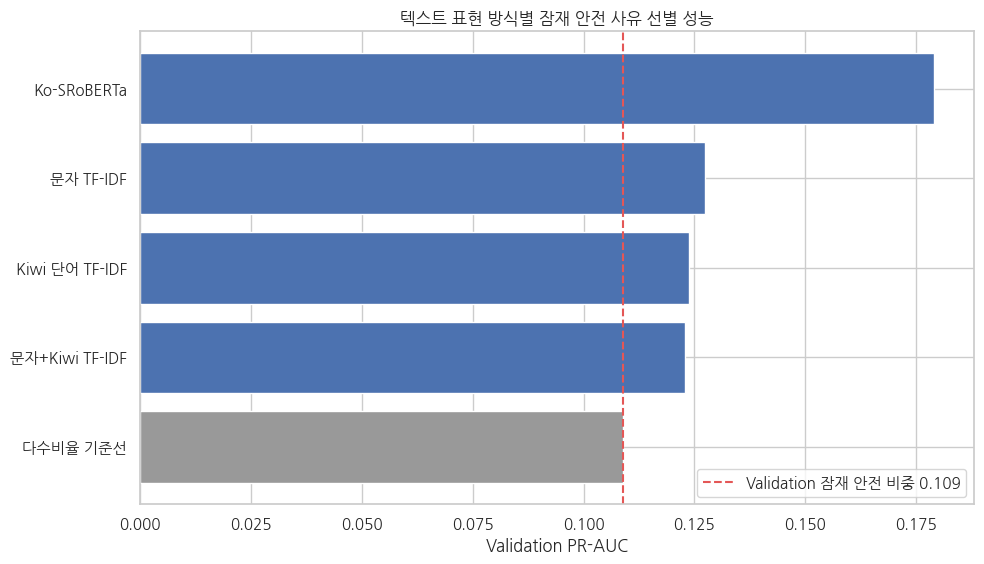

In [ ]:
# 텍스트 모델 검증 성능 비교
td_train_idx = td_pair.index[td_pair['split'].eq('train')]
td_val_idx = td_pair.index[td_pair['split'].eq('validation')]
td_test_idx = td_pair.index[td_pair['split'].eq('test')]
td_y_train = td_pair.loc[td_train_idx, 'potential_safety'].to_numpy()
td_y_val = td_pair.loc[td_val_idx, 'potential_safety'].to_numpy()
td_y_test = td_pair.loc[td_test_idx, 'potential_safety'].to_numpy()
td_model_objects = {}
td_validation_predictions = {}
td_registry = []

def td_register_validation(td_name, td_y, td_p, td_threshold, td_seconds):
    td_row = {'model': td_name, 'fit_seconds': td_seconds, **td_eval_binary(td_y, td_p, td_threshold)}
    td_registry.append(td_row)
td_base_prob = float(td_y_train.mean())
td_p_base_val = np.repeat(td_base_prob, len(td_y_val))
td_register_validation('다수비율 기준선', td_y_val, td_p_base_val, 0.5, 0.0)
td_validation_predictions['다수비율 기준선'] = td_p_base_val
td_t0 = time.time()
td_char_vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, max_features=50000, sublinear_tf=True)
td_Xc_train = td_char_vec.fit_transform(td_pair.loc[td_train_idx, 'normalized_text'])
td_Xc_val = td_char_vec.transform(td_pair.loc[td_val_idx, 'normalized_text'])
td_char_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED)
td_char_model.fit(td_Xc_train, td_y_train)
td_p_char_val = td_char_model.predict_proba(td_Xc_val)[:, 1]
td_t_char = td_best_bacc_threshold(td_y_val, td_p_char_val)
td_register_validation('문자 TF-IDF', td_y_val, td_p_char_val, td_t_char, time.time() - td_t0)
td_validation_predictions['문자 TF-IDF'] = td_p_char_val
td_model_objects['문자 TF-IDF'] = (td_char_vec, td_char_model)
td_t0 = time.time()
td_word_vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2, max_features=30000, sublinear_tf=True)
td_Xw_train = td_word_vec.fit_transform(td_pair.loc[td_train_idx, 'token_text'].fillna(''))
td_Xw_val = td_word_vec.transform(td_pair.loc[td_val_idx, 'token_text'].fillna(''))
td_word_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED)
td_word_model.fit(td_Xw_train, td_y_train)
td_p_word_val = td_word_model.predict_proba(td_Xw_val)[:, 1]
td_t_word = td_best_bacc_threshold(td_y_val, td_p_word_val)
td_register_validation('Kiwi 단어 TF-IDF', td_y_val, td_p_word_val, td_t_word, time.time() - td_t0)
td_validation_predictions['Kiwi 단어 TF-IDF'] = td_p_word_val
td_model_objects['Kiwi 단어 TF-IDF'] = (td_word_vec, td_word_model)
td_t0 = time.time()
td_Xcw_train = sparse.hstack([td_Xc_train, td_Xw_train], format='csr')
td_Xcw_val = sparse.hstack([td_Xc_val, td_Xw_val], format='csr')
td_combo_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED)
td_combo_model.fit(td_Xcw_train, td_y_train)
td_p_combo_val = td_combo_model.predict_proba(td_Xcw_val)[:, 1]
td_t_combo = td_best_bacc_threshold(td_y_val, td_p_combo_val)
td_register_validation('문자+Kiwi TF-IDF', td_y_val, td_p_combo_val, td_t_combo, time.time() - td_t0)
td_validation_predictions['문자+Kiwi TF-IDF'] = td_p_combo_val
td_model_objects['문자+Kiwi TF-IDF'] = ((td_char_vec, td_word_vec), td_combo_model)

def td_embedding_matrix(td_frame):
    td_idx = td_frame['normalized_text'].map(td_embedding_index)
    td_out = np.zeros((len(td_frame), td_embeddings.shape[1]), dtype='float32')
    td_present = td_idx.notna().to_numpy()
    if td_present.any():
        td_out[td_present] = td_embeddings[td_idx.loc[td_idx.notna()].astype(int).to_numpy()]
    return td_out
td_t0 = time.time()
td_Xe_train = td_embedding_matrix(td_pair.loc[td_train_idx])
td_Xe_val = td_embedding_matrix(td_pair.loc[td_val_idx])
td_emb_model = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED)
td_emb_model.fit(td_Xe_train, td_y_train)
td_p_emb_val = td_emb_model.predict_proba(td_Xe_val)[:, 1]
td_t_emb = td_best_bacc_threshold(td_y_val, td_p_emb_val)
td_register_validation('Ko-SRoBERTa', td_y_val, td_p_emb_val, td_t_emb, time.time() - td_t0)
td_validation_predictions['Ko-SRoBERTa'] = td_p_emb_val
td_model_objects['Ko-SRoBERTa'] = (None, td_emb_model)
td_model_registry = pd.DataFrame(td_registry).sort_values('pr_auc', ascending=False)
display(td_model_registry)
td_fig, td_ax = plt.subplots(figsize=(10, 5.8))
td_plot = td_model_registry.sort_values('pr_auc')
td_ax.barh(td_plot['model'], td_plot['pr_auc'], color=np.where(td_plot['model'].eq('다수비율 기준선'), '#999999', '#4C72B0'))
td_ax.axvline(td_y_val.mean(), color='#E45756', linestyle='--', label=f'Validation 잠재 안전 비중 {td_y_val.mean():.3f}')
td_ax.set_xlabel('Validation PR-AUC')
td_ax.set_title('텍스트 표현 방식별 잠재 안전 사유 선별 성능')
td_ax.legend()
td_savefig('14_model_validation_pr_auc.png')
plt.close('all')
_t7tc_collected = gc.collect()


- 검증 PR-AUC는 Ko-SRoBERTa 0.1791, 문자 TF-IDF 0.1275, Kiwi 단어 TF-IDF 0.1237, 결합 TF-IDF 0.1228이다.
- 검증 PR-AUC가 가장 높은 Ko-SRoBERTa를 선택했고, 검증 표본에서 정한 임계값은 0.398이다.


,model,metric,estimate,ci_low,ci_high,baseline,selected_threshold,fit_seconds
0,Ko-SRoBERTa,pr_auc,0.1552,0.1231,0.1948,0.1154,0.3980,26.9250
1,Ko-SRoBERTa,roc_auc,0.5984,0.5208,0.6771,0.5000,0.3980,26.9250
2,Ko-SRoBERTa,balanced_accuracy,0.5554,0.4888,0.6298,0.5000,0.3980,26.9250
3,Ko-SRoBERTa,f1,0.2243,0.1758,0.2728,0.0000,0.3980,26.9250
4,Ko-SRoBERTa,precision,0.1376,0.1059,0.1691,0.0000,0.3980,26.9250
5,Ko-SRoBERTa,recall,0.6053,0.4496,0.7660,0.0000,0.3980,26.9250
6,Ko-SRoBERTa,brier,0.2134,0.1908,0.2361,0.1022,0.3980,26.9250
7,Ko-SRoBERTa,precision_at_top_10pct,0.1521,0.1099,0.2086,0.1154,0.3980,26.9250


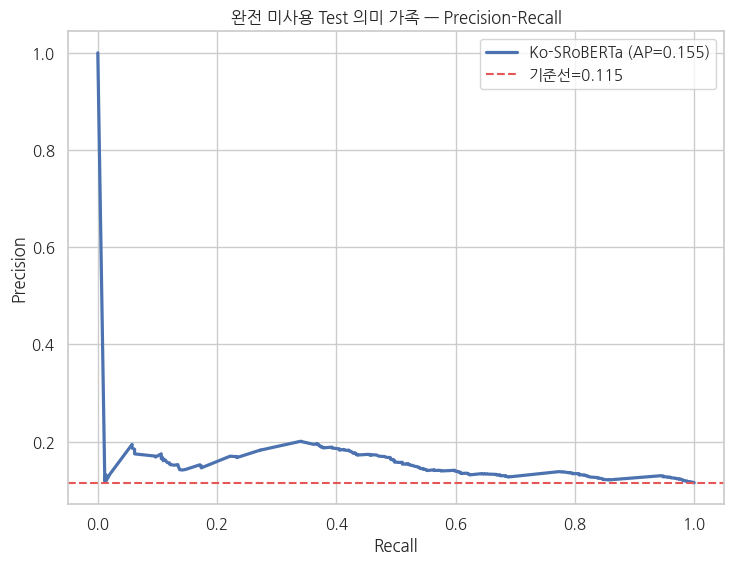

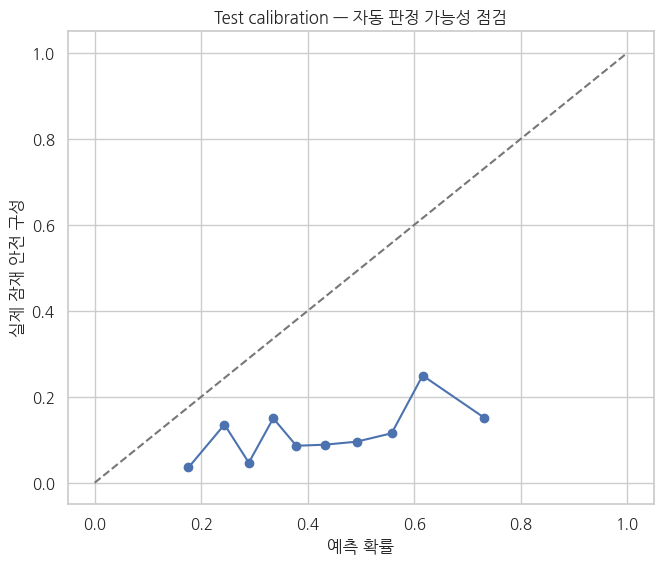

선택 모델: Ko-SRoBERTa, Validation에서 고정한 임계값: 0.398


In [ ]:
# 최종 테스트·확률 보정 점검
td_selected_name = td_model_registry.loc[td_model_registry['model'].ne('다수비율 기준선')].iloc[0]['model']
td_selected_threshold = float(td_model_registry.loc[td_model_registry['model'].eq(td_selected_name), 'threshold'].iloc[0])
td_trainval = td_pair.loc[td_pair['split'].isin(['train', 'validation'])].copy()
td_y_trainval = td_trainval['potential_safety'].to_numpy()
td_test_frame = td_pair.loc[td_test_idx].copy()
td_t0 = time.time()
if td_selected_name == '문자 TF-IDF':
    td_final_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, max_features=50000, sublinear_tf=True)
    td_Xtr = td_final_char.fit_transform(td_trainval['normalized_text'])
    td_Xte = td_final_char.transform(td_test_frame['normalized_text'])
    td_final_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED).fit(td_Xtr, td_y_trainval)
elif td_selected_name == 'Kiwi 단어 TF-IDF':
    td_final_word = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2, max_features=30000, sublinear_tf=True)
    td_Xtr = td_final_word.fit_transform(td_trainval['token_text'].fillna(''))
    td_Xte = td_final_word.transform(td_test_frame['token_text'].fillna(''))
    td_final_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED).fit(td_Xtr, td_y_trainval)
elif td_selected_name == '문자+Kiwi TF-IDF':
    td_final_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=3, max_features=50000, sublinear_tf=True)
    td_final_word = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False, ngram_range=(1, 2), min_df=2, max_features=30000, sublinear_tf=True)
    td_Xtr = sparse.hstack([td_final_char.fit_transform(td_trainval['normalized_text']), td_final_word.fit_transform(td_trainval['token_text'].fillna(''))], format='csr')
    td_Xte = sparse.hstack([td_final_char.transform(td_test_frame['normalized_text']), td_final_word.transform(td_test_frame['token_text'].fillna(''))], format='csr')
    td_final_model = LogisticRegression(max_iter=1500, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED).fit(td_Xtr, td_y_trainval)
else:
    td_Xtr = td_embedding_matrix(td_trainval)
    td_Xte = td_embedding_matrix(td_test_frame)
    td_final_model = LogisticRegression(max_iter=2000, class_weight='balanced', C=1.0, solver='liblinear', random_state=td_SEED).fit(td_Xtr, td_y_trainval)
td_p_test = td_final_model.predict_proba(td_Xte)[:, 1]
td_final_metrics = td_eval_binary(td_y_test, td_p_test, td_selected_threshold)
td_baseline_metrics = td_eval_binary(td_y_test, np.repeat(td_y_trainval.mean(), len(td_y_test)), 0.5)
td_test_groups = td_test_frame['semantic_group_090'].to_numpy()
td_unique_groups = np.unique(td_test_groups)
td_boot_metrics = []
for td__ in range(300):
    td_sampled = td_RNG.choice(td_unique_groups, size=len(td_unique_groups), replace=True)
    td_idx_parts = [np.flatnonzero(td_test_groups == td_g) for td_g in td_sampled]
    td_idx_b = np.concatenate(td_idx_parts)
    if len(np.unique(td_y_test[td_idx_b])) < 2:
        continue
    td_boot_metrics.append(td_eval_binary(td_y_test[td_idx_b], td_p_test[td_idx_b], td_selected_threshold))
td_boot_df = pd.DataFrame(td_boot_metrics)
td_metric_rows = []
for td_metric, td_value in td_final_metrics.items():
    if td_metric == 'threshold':
        continue
    td_metric_rows.append({'model': td_selected_name, 'metric': td_metric, 'estimate': td_value, 'ci_low': td_boot_df[td_metric].quantile(0.025), 'ci_high': td_boot_df[td_metric].quantile(0.975), 'baseline': td_baseline_metrics.get(td_metric, np.nan)})
td_final_test = pd.DataFrame(td_metric_rows)
td_final_test['selected_threshold'] = td_selected_threshold
td_final_test['fit_seconds'] = time.time() - td_t0
display(td_final_test)
td_precision, td_recall, td__ = precision_recall_curve(td_y_test, td_p_test)
td_fig, td_ax = plt.subplots(figsize=(7.5, 5.8))
td_ax.plot(td_recall, td_precision, color='#4C72B0', linewidth=2.3, label=f"{td_selected_name} (AP={td_final_metrics['pr_auc']:.3f})")
td_ax.axhline(td_y_test.mean(), color='#E45756', linestyle='--', label=f'기준선={td_y_test.mean():.3f}')
td_ax.set_xlabel('Recall')
td_ax.set_ylabel('Precision')
td_ax.set_title('테스트 표본 — Precision-Recall')
td_ax.legend()
td_savefig('15_final_test_precision_recall.png')
td_prob_true, td_prob_pred = calibration_curve(td_y_test, td_p_test, n_bins=10, strategy='quantile')
td_fig, td_ax = plt.subplots(figsize=(6.8, 5.8))
td_ax.plot(td_prob_pred, td_prob_true, marker='o', color='#4C72B0')
td_ax.plot([0, 1], [0, 1], linestyle='--', color='#777777')
td_ax.set_xlabel('예측 확률')
td_ax.set_ylabel('실제 잠재 안전 구성')
td_ax.set_title('Test calibration — 자동 판정 가능성 점검')
td_savefig('15b_final_test_calibration.png')
print(f'선택 모델: {td_selected_name}, Validation에서 고정한 임계값: {td_selected_threshold:.3f}')
plt.close('all')
_t7tc_collected = gc.collect()


**결과**

- Ko-SRoBERTa의 테스트 PR-AUC는 0.1552, ROC-AUC는 0.5984다. 상위 10% 점수의 정밀도는 15.21%, 테스트 전체 잠재 안전 비중은 11.54%다.
- 문구 중복 한계가 남아 있어 완전히 새로운 문구의 자동 유해성 판정 성과로 해석하지 않는다.


,text_label_structure,texts,events,safety_events,text_share_pct,event_share_pct,safety_event_share_pct
0,비안전 사유만,1746,9682,0,58.8473,18.8311,0.0000
1,안전·비안전 혼합,1153,41657,5618,38.8608,81.0211,98.6653
2,잠재 안전 사유만,68,76,76,2.2919,0.1478,1.3347


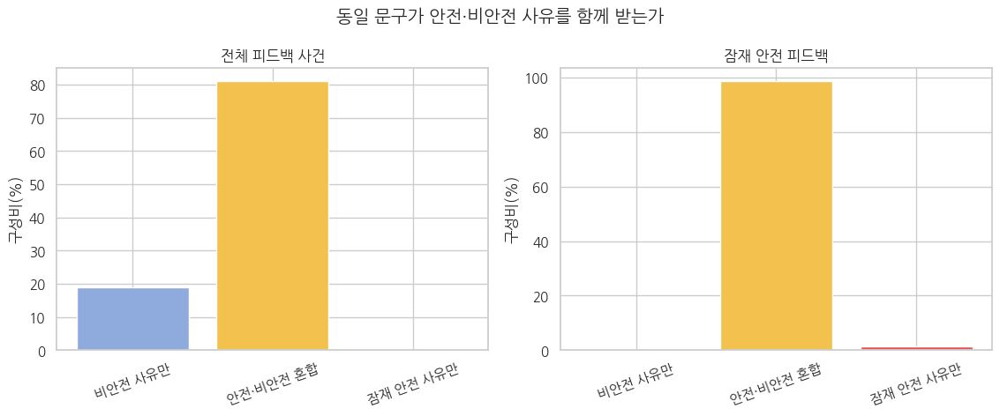

,error_type,question_text,pred_prob,potential_safety,lex_any,theme_label_ko
6157,false_negative,학교에서 모르는 사람이 없을 것 같은 사람,0.0592,1,0,학교·공부
11258,false_negative,10년이 지나도 늙지 않고 그대로일 것 같은 사람은?,0.1011,1,0,능력·성숙·신뢰
5248,false_negative,매너가 제일 좋은 사람은?,0.1356,1,0,능력·성숙·신뢰
969,false_negative,계획을 짜임새있게 잘 세우는 사람은?,0.1452,1,0,능력·성숙·신뢰
23747,false_negative,내가 좋은 일이 있을 때 가장 축하를 잘해줄 것 같은 사람은?,0.1550,1,0,생일·선물
39575,false_negative,가장 내가 아끼는 사람은?,0.1572,1,0,연애·호감
27681,false_negative,배우가 잘 어울리는 사람은?,0.1579,1,0,연애·호감
39613,false_negative,가장 인맥이 넓은 사람은?,0.1608,1,0,친구 성격·친화력
15221,false_negative,책을 제일 많이 읽은 것 같은 사람은?,0.1697,1,0,글쓰기·목소리·표현
5131,false_negative,조각케이크 위 딸기를 나눠줄 것 같은 사람은?,0.1783,1,0,음식·식사


In [ ]:
# 동일 문구의 혼합 사유·오류 예시
td_text_mix = td_linked.groupby('normalized_text', as_index=False).agg(events=('potential_safety', 'size'), safety_events=('potential_safety', 'sum'), question_text=('question_text', 'first'))
td_text_mix['other_events'] = td_text_mix['events'] - td_text_mix['safety_events']
td_text_mix['text_label_structure'] = np.select([td_text_mix['safety_events'].eq(0), td_text_mix['other_events'].eq(0)], ['비안전 사유만', '잠재 안전 사유만'], default='안전·비안전 혼합')
td_mix_summary = td_text_mix.groupby('text_label_structure', as_index=False).agg(texts=('normalized_text', 'size'), events=('events', 'sum'), safety_events=('safety_events', 'sum'))
td_mix_summary['text_share_pct'] = td_mix_summary['texts'] / td_mix_summary['texts'].sum() * 100
td_mix_summary['event_share_pct'] = td_mix_summary['events'] / td_mix_summary['events'].sum() * 100
td_mix_summary['safety_event_share_pct'] = td_mix_summary['safety_events'] / td_mix_summary['safety_events'].sum() * 100
display(td_mix_summary)
td_fig, td_axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
td_colors = {'비안전 사유만': '#8FAADC', '잠재 안전 사유만': '#E45756', '안전·비안전 혼합': '#F2C14E'}
for td_ax, td_value, td_title in zip(td_axes, ['event_share_pct', 'safety_event_share_pct'], ['전체 피드백 사건', '잠재 안전 피드백']):
    td_plot = td_mix_summary.set_index('text_label_structure')[td_value]
    td_ax.bar(td_plot.index, td_plot.values, color=[td_colors[td_i] for td_i in td_plot.index])
    td_ax.set_title(td_title)
    td_ax.set_ylabel('구성비(%)')
    td_ax.tick_params(axis='x', rotation=20)
plt.suptitle('동일 문구가 안전·비안전 사유를 함께 받는가')
td_savefig('16_same_text_mixed_feedback_structure.png')
td_test_frame = td_test_frame.copy()
td_test_frame['pred_prob'] = td_p_test
td_test_frame['pred'] = (td_p_test >= td_selected_threshold).astype(int)
td_test_frame['error_type'] = np.select([td_test_frame['potential_safety'].eq(1) & td_test_frame['pred'].eq(0), td_test_frame['potential_safety'].eq(0) & td_test_frame['pred'].eq(1)], ['false_negative', 'false_positive'], default='correct')
td_error_examples = pd.concat([td_test_frame.loc[td_test_frame['error_type'].eq('false_negative')].sort_values('pred_prob').drop_duplicates('normalized_text').head(20), td_test_frame.loc[td_test_frame['error_type'].eq('false_positive')].sort_values('pred_prob', ascending=False).drop_duplicates('normalized_text').head(20)])[['error_type', 'question_text', 'pred_prob', 'potential_safety', 'lex_any', 'theme_label_ko']]
display(td_error_examples.head(12))
plt.close('all')
_t7tc_collected = gc.collect()


- 안전·비안전 사유를 모두 받은 문구에 잠재 안전 사건의 98.7%가 포함돼 있다. 같은 문구라도 반응이 한 방향으로 모이지 않았다. 누구를 후보로 보았는지, 어떤 관계인지가 추가로 필요해 보인다.


In [ ]:
# 표현 사전의 누락·오탐
td_lex_test = td_pair.loc[td_pair['split'].eq('test')].copy()
td_lex_precision = td_lex_test.loc[td_lex_test['lex_any'].eq(1), 'potential_safety'].mean()
td_lex_recall = td_lex_test.loc[td_lex_test['potential_safety'].eq(1), 'lex_any'].mean()
td_lex_flag_rate = td_lex_test['lex_any'].mean()
td_lex_lift = td_lex_precision / td_lex_test['potential_safety'].mean()
td_lex_screen = pd.DataFrame([{'test_rows': len(td_lex_test), 'base_safety_share': td_lex_test['potential_safety'].mean(), 'flag_rate': td_lex_flag_rate, 'precision': td_lex_precision, 'recall': td_lex_recall, 'precision_lift_vs_base': td_lex_lift, 'false_positive_share_among_flagged': 1 - td_lex_precision, 'missed_safety_share': 1 - td_lex_recall}])
display(td_lex_screen)
td_missed = td_lex_test.loc[td_lex_test['potential_safety'].eq(1) & td_lex_test['lex_any'].eq(0)].groupby('normalized_text', as_index=False).agg(question_text=('question_text', 'first'), missed_safety_pairs=('potential_safety', 'size'), theme_label_ko=('theme_label_ko', 'first')).sort_values('missed_safety_pairs', ascending=False).head(25)
td_false_flags = td_lex_test.loc[td_lex_test['potential_safety'].eq(0) & td_lex_test['lex_any'].eq(1)].groupby('normalized_text', as_index=False).agg(question_text=('question_text', 'first'), non_safety_pairs=('potential_safety', 'size'), theme_label_ko=('theme_label_ko', 'first')).sort_values('non_safety_pairs', ascending=False).head(25)
print('사전에 걸리지 않은 잠재 안전 표본')
display(td_missed.head(10))
print('사전에는 걸렸지만 비안전 사유였던 표본')
display(td_false_flags.head(10))
plt.close('all')
_t7tc_collected = gc.collect()


,test_rows,base_safety_share,flag_rate,precision,recall,precision_lift_vs_base,false_positive_share_among_flagged,missed_safety_share
0,8148,0.1154,0.1262,0.3113,0.3404,2.6982,0.6887,0.6596


사전에 걸리지 않은 잠재 안전 표본


,normalized_text,question_text,missed_safety_pairs,theme_label_ko
143,이모티콘만 보고 알아서 상상해서 골라봐,이모티콘만 보고 알아서 상상해서 골라봐,82,매력·외모
80,먹방 찍으면 100만 유튜버가 될 것 같은 친구,먹방 찍으면 100만 유튜버가 될 것 같은 친구,33,SNS·연예인 이미지
77,맥날 성애자,맥날 성애자,20,두려움·부정 성향
182,커플요가를 같이 하고싶은 사람은,커플요가를 같이 하고싶은 사람은?,17,연애·호감
157,제일 듬직한 사람은,제일 듬직한 사람은?,14,능력·성숙·신뢰
23,가장 이성친구가 많을 것 같은 사람은,가장 이성친구가 많을 것 같은 사람은?,14,연애·호감
98,삭발 어울릴 것 같은 친구,삭발 어울릴 것 같은 친구,13,패션·헤어
74,많이 먹어도 몸무게가 그대로일 것 같은 사람은,많이 먹어도 몸무게가 그대로일 것 같은 사람은?,12,음식·식사
150,잠시라도 이성으로 보인 적 있다,잠시라도 이성으로 보인 적 있다,9,매력·외모
107,솔직히 얘는 나 좋아했을 것 같다,솔직히 얘는 나 좋아했을 것 같다,9,연애·호감


사전에는 걸렸지만 비안전 사유였던 표본


,normalized_text,question_text,non_safety_pairs,theme_label_ko
16,첫 키스를 가장 먼저 해봤을 것 같은 사람은,첫 키스를 가장 먼저 해봤을 것 같은 사람은?,126,결혼·가족·미래
7,발가락이 귀여울 것 같은 친구는,발가락이 귀여울 것 같은 친구는?,100,친구 성격·친화력
0,가장 매력적인 사람은,가장 매력적인 사람은?,90,매력·외모
5,마스크 벗은 모습이 궁금한 사람은,마스크 벗은 모습이 궁금한 사람은?,82,매력·외모
10,스킨십이 가장 능숙할 것 같은 사람은,스킨십이 가장 능숙할 것 같은 사람은?,66,게임·운동·장난
18,플러팅을 제일 잘하는 사람은,플러팅을 제일 잘하는 사람은?,65,게임·운동·장난
15,전남친여친 sns 염탐할 것 같은 사람은,전남친/여친 SNS 염탐할 것 같은 사람은?,55,연애·호감
3,내 어깨를 내어줄 수 있는 사람은,내 어깨를 내어줄 수 있는 사람은?,26,배려·유쾌함
11,얼굴을 가장 막 쓰는 사람은,얼굴을 가장 막 쓰는 사람은?,22,매력·외모
6,반에서 몰폰을 가장 많이 하는 사람은,반에서 몰폰을 가장 많이 하는 사람은?,22,학교·공부


- 핵심 네 범주 사전의 테스트 정밀도는 31.1%, 재현율은 34.0%다. 탐지 표본 중 68.9%는 비안전 사유이며, 잠재 안전 표본의 66.0%를 놓쳤다.
- 미탐 사례에는 ‘이모티콘만 보고 알아서 상상해서 골라봐’ 82쌍 등이 포함됐다. 사전에 정한 범주만으로 모든 잠재 안전 반응을 설명하기 어렵다.


### 3-6-9. 조건별 비교와 검수 표본

- 전체 피드백, 사용자·문구 중복 제거, 5월 한정 조건을 비교했다. 건수·비중·사전 탐지 여부에 따라 사람 검수용 문구를 추출했다.


dataset,2023년 5월 actor-text,2023년 5월 원행,actor-text 중복제거,원행 전체
category,,,,
맥락 불명·강제 상상,10.1738,7.6602,9.5108,6.7738
배려·신뢰·친사회,-6.1600,-7.1522,-6.3754,-7.3089
부정 낙인·조롱,-0.1986,0.5838,0.3039,1.0692
사생활·감시 추정,25.9154,26.6022,27.5341,28.0649
연애·친밀행동 추정,18.1415,17.9227,17.5698,17.1079
외모·신체 평가,14.9659,15.4722,14.8311,15.6745
음식·섭취 취향 추정,10.2767,10.6335,10.8340,11.0773
체취·위생·신체 희화,20.5318,20.4447,20.0803,19.9477


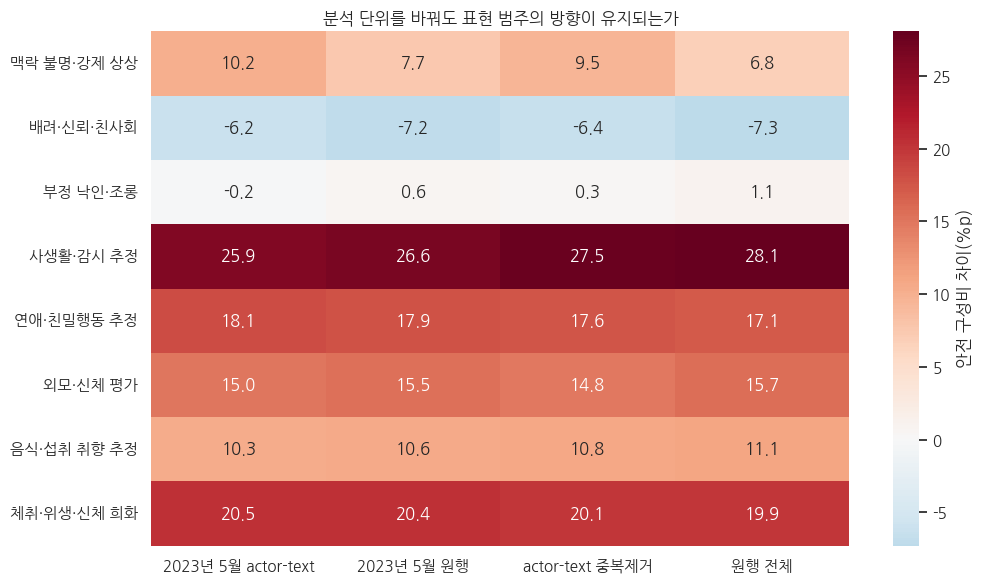

In [ ]:
# 분석 기간·중복 처리 민감도
for td_category, td_words in td_LEXICON.items():
    td_linked[f'lex_{td_category}'] = td_linked['normalized_text'].map(lambda td_x: td_lexicon_flag(td_x, td_words))
td_sensitivity_rows = []
td_datasets = {'원행 전체': td_linked, 'actor-text 중복제거': td_pair, '2023년 5월 원행': td_linked.loc[td_linked['event_month'].eq('2023-05')], '2023년 5월 actor-text': td_pair.loc[td_pair['event_month'].eq('2023-05')]}
for td_data_name, td_frame in td_datasets.items():
    for td_category in td_LEXICON:
        td_col = f'lex_{td_category}'
        td_present = td_frame[td_col].eq(1)
        if td_present.sum() == 0:
            continue
        td_rate_with = td_frame.loc[td_present, 'potential_safety'].mean()
        td_rate_without = td_frame.loc[~td_present, 'potential_safety'].mean()
        td_sensitivity_rows.append({'dataset': td_data_name, 'category': td_category, 'rows_with_flag': int(td_present.sum()), 'safety_share_with': td_rate_with, 'safety_share_without': td_rate_without, 'delta_pp': (td_rate_with - td_rate_without) * 100, 'risk_ratio': td_rate_with / td_rate_without if td_rate_without else np.nan})
td_sensitivity = pd.DataFrame(td_sensitivity_rows)
td_pivot = td_sensitivity.pivot(index='category', columns='dataset', values='delta_pp')
display(td_pivot)
td_fig, td_ax = plt.subplots(figsize=(10.5, 6))
sns.heatmap(td_pivot, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=td_ax, cbar_kws={'label': '안전 구성비 차이(%p)'})
td_ax.set_title('분석 단위를 바꿔도 표현 범주의 방향이 유지되는가')
td_ax.set_xlabel('')
td_ax.set_ylabel('')
td_savefig('18_lexicon_sensitivity_heatmap.png')
plt.close('all')
_t7tc_collected = gc.collect()


- 사생활·감시 추정의 잠재 안전 비중 차이는 조건을 바꿔도 약 26~28%p로 유지된다. 반면 부정 낙인·조롱은 약 -0.2~1.1%p로 작고 방향도 달라진다. 모든 표현 범주에서 같은 정도로 안정적인 결과가 나온 것은 아니다.


In [ ]:
# 사람 검수용 층화 표본
td_review_parts = []
td_used_texts = set()

def td_add_review_sample(td_frame, td_stratum, td_n):
    td_candidates = td_frame.loc[~td_frame['normalized_text'].isin(td_used_texts)].copy()
    if td_candidates.empty:
        return
    td_take = td_candidates.sample(min(td_n, len(td_candidates)), random_state=td_SEED + len(td_review_parts))
    td_take['sample_stratum'] = td_stratum
    td_review_parts.append(td_take)
    td_used_texts.update(td_take['normalized_text'])
td_add_review_sample(td_text_stats.nlargest(200, 'safety_pairs'), '잠재안전 건수 상위', 40)
td_add_review_sample(td_text_stats.loc[td_text_stats['feedback_pairs'].ge(10)].nlargest(200, 'eb_safety_share'), '안전 구성비 상위', 40)
td_add_review_sample(td_text_stats.loc[td_text_stats['lex_any'].eq(1)], '핵심 표현 사전 플래그', 40)
td_add_review_sample(td_text_stats.loc[td_text_stats['lex_any'].eq(0) & td_text_stats['safety_pairs'].gt(0)], '사전 미탐 잠재안전', 40)
td_add_review_sample(td_text_stats, '무작위 대조', 40)
td_review_sample = pd.concat(td_review_parts, ignore_index=True)
td_review_sample = td_review_sample[['sample_stratum', 'question_text', 'normalized_text', 'feedback_pairs', 'safety_pairs', 'eb_safety_share', 'theme_label_ko']]
td_review_sample['reviewer_a_category'] = ''
td_review_sample['reviewer_b_category'] = ''
td_review_sample['reviewer_a_harm_flag'] = ''
td_review_sample['reviewer_b_harm_flag'] = ''
td_review_sample['reviewer_note'] = ''
print(f'블라인드 사람 검수용 표본 {len(td_review_sample)}개 생성')
display(td_review_sample.groupby('sample_stratum').size().rename('texts').to_frame())
plt.close('all')
_t7tc_collected = gc.collect()


블라인드 사람 검수용 표본 200개 생성


,texts
sample_stratum,
무작위 대조,40
사전 미탐 잠재안전,40
안전 구성비 상위,40
잠재안전 건수 상위,40
핵심 표현 사전 플래그,40


- 검수 표본 200개는 잠재 안전 건수 상위·비중 상위·사전 탐지·사전 미탐·무작위 대조에서 각각 40개씩 추출했다.
- 의도적으로 구성한 표본이므로 전체 질문의 유해 비율 추정에는 사용하지 않는다.


In [ ]:
# Trust 검증·근거 정리
td_qa_rows = [('원천 질문 피드백 행 보존', 'PASS' if len(td_feedback) == 51424 else 'FAIL', f'rows={len(td_feedback):,}'), ('질문 문구 연결', 'PASS' if td_feedback['normalized_text'].notna().mean() > 0.999 else 'WARN', f"link={td_feedback['normalized_text'].notna().mean():.4%}"), ('잠재 안전 라벨 분리', 'PASS' if td_feedback['potential_safety'].sum() == 5694 else 'FAIL', f"potential_safety={td_feedback['potential_safety'].sum():,}"), ('actor-text 반복 제거 기록', 'PASS', f"raw={len(td_linked):,}, pure_pairs={len(td_pair):,}, mixed={td_pair_raw['mixed_reason_pair'].sum():,}"), ('semantic family split 누수', 'PASS' if td_pair.groupby('semantic_group_090')['split'].nunique().max() == 1 else 'FAIL', 'max split per family=' + str(td_pair.groupby('semantic_group_090')['split'].nunique().max())), ('정규화 문구 split 추가 점검', 'PASS' if td_pair.groupby('normalized_text')['split'].nunique().max() == 1 else 'WARN', 'max split per text=' + str(td_pair.groupby('normalized_text')['split'].nunique().max())), ('Test 선행 사용 금지', 'PASS', '어휘 후보=Train, 모델 선택=Validation, 최종 성능=Test'), ('노출 분모 사용 금지', 'PASS', '모든 결과를 피드백 내 사유 구성으로 명명'), ('다중검정 보정', 'PASS', 'lexicon/token BH-FDR 적용'), ('실제 위해 확정 표현 금지', 'PASS', 'potential safety reason으로 제한')]
td_final_qa = pd.DataFrame(td_qa_rows, columns=['check', 'status', 'detail'])
display(td_final_qa)
td_mix_lookup = td_mix_summary.set_index('text_label_structure')
td_mixed_safety_share = float(td_mix_lookup.loc['안전·비안전 혼합', 'safety_event_share_pct'])
td_mixed_event_share = float(td_mix_lookup.loc['안전·비안전 혼합', 'event_share_pct'])
td_evidence = pd.DataFrame([{'finding': '피드백 채널의 의미가 혼합됨', 'evidence': f"개인 선호 {td_domain_counts.set_index('domain').loc['PERSONAL_PREFERENCE', 'share_pct']:.1f}%, 잠재 안전 {td_domain_counts.set_index('domain').loc['CONTENT_SAFETY', 'share_pct']:.1f}%", 'strength': '관측 확인', 'allowed_claim': '전체 질문 피드백을 안전 신고로 해석할 수 없다'}, {'finding': '잠재 안전 신호가 일부 문구에 집중', 'evidence': f"상위 1% 문구가 actor-text 잠재 안전 신호의 {td_safety_sorted.head(max(1, int(len(td_safety_sorted) * 0.01)))['safety_pairs'].sum() / td_safety_sorted['safety_pairs'].sum() * 100:.1f}% 포함", 'strength': '중복 사용자 제거 후 관측', 'allowed_claim': '검수 우선순위 집중은 가능하나 노출 대비 위험률은 아님'}, {'finding': '평가·추정 표현 범주와 잠재 안전 사유가 함께 나타남', 'evidence': '감시, 체취·위생 희화, 친밀행동 추정, 외모·신체 평가 범주를 고정 Test와 조정모형으로 확인', 'strength': '검증셋 연관', 'allowed_claim': '자동 유해 판정이 아니라 검수 우선순위 신호'}, {'finding': '같은 문구도 서로 다른 피드백을 받음', 'evidence': f'혼합 문구가 전체 사건 {td_mixed_event_share:.1f}%, 잠재 안전 사건 {td_mixed_safety_share:.1f}%를 포함', 'strength': '관측 확인', 'allowed_claim': '문구 외 후보·관계·반복 맥락이 중요하다'}, {'finding': '텍스트 단독 선별력은 제한적', 'evidence': f"최종 {td_selected_name} Test PR-AUC {td_final_metrics['pr_auc']:.3f}, 상위10% 정밀도 {td_final_metrics['precision_at_top_10pct']:.3f}", 'strength': '미사용 Test', 'allowed_claim': '자동 차단이 아니라 검수 보조에 한정'}])
display(td_evidence)
td_summary = {'rows_feedback': int(len(td_feedback)), 'rows_potential_safety': int(td_feedback['potential_safety'].sum()), 'linked_text_rate': float(td_feedback['normalized_text'].notna().mean()), 'primary_actor_text_rows': int(len(td_pair)), 'primary_unique_texts': int(td_pair['normalized_text'].nunique()), 'max_splits_per_text': int(td_pair.groupby('normalized_text')['split'].nunique().max()), 'primary_safety_share': float(td_pair['potential_safety'].mean()), 'selected_model': td_selected_name, 'test_metrics': {td_k: float(td_v) for td_k, td_v in td_final_metrics.items()}, 'mixed_text_event_share_pct': td_mixed_event_share, 'mixed_text_safety_event_share_pct': td_mixed_safety_share, 'qa_fail_count': int(td_final_qa['status'].eq('FAIL').sum())}
print(json.dumps(td_summary, ensure_ascii=False, indent=2))
plt.close('all')
_t7tc_collected = gc.collect()


,check,status,detail
0,원천 질문 피드백 행 보존,PASS,"rows=51,424"
1,질문 문구 연결,PASS,link=99.9825%
2,잠재 안전 라벨 분리,PASS,"potential_safety=5,694"
3,actor-text 반복 제거 기록,PASS,"raw=51,415, pure_pairs=44,024, mixed=569"
4,semantic family split 누수,PASS,max split per family=1
5,정규화 문구 split 추가 점검,WARN,max split per text=3
6,Test 선행 사용 금지,PASS,"어휘 후보=Train, 모델 선택=Validation, 최종 성능=Test"
7,노출 분모 사용 금지,PASS,모든 결과를 피드백 내 사유 구성으로 명명
8,다중검정 보정,PASS,lexicon/token BH-FDR 적용
9,실제 위해 확정 표현 금지,PASS,potential safety reason으로 제한


,finding,evidence,strength,allowed_claim
0,피드백 채널의 의미가 혼합됨,"개인 선호 73.9%, 잠재 안전 11.1%",관측 확인,전체 질문 피드백을 안전 신고로 해석할 수 없다
1,잠재 안전 신호가 일부 문구에 집중,상위 1% 문구가 actor-text 잠재 안전 신호의 40.1% 포함,중복 사용자 제거 후 관측,검수 우선순위 집중은 가능하나 노출 대비 위험률은 아님
2,평가·추정 표현 범주와 잠재 안전 사유가 함께 나타남,"감시, 체취·위생 희화, 친밀행동 추정, 외모·신체 평가 범주를 고정 Test와 조...",검증셋 연관,자동 유해 판정이 아니라 검수 우선순위 신호
3,같은 문구도 서로 다른 피드백을 받음,"혼합 문구가 전체 사건 81.0%, 잠재 안전 사건 98.7%를 포함",관측 확인,문구 외 후보·관계·반복 맥락이 중요하다
4,텍스트 단독 선별력은 제한적,"최종 Ko-SRoBERTa Test PR-AUC 0.155, 상위10% 정밀도 0.152",미사용 Test,자동 차단이 아니라 검수 보조에 한정


{
  "rows_feedback": 51424,
  "rows_potential_safety": 5694,
  "linked_text_rate": 0.9998249844430616,
  "primary_actor_text_rows": 44024,
  "primary_unique_texts": 2963,
  "max_splits_per_text": 3,
  "primary_safety_share": 0.10644194075958568,
  "selected_model": "Ko-SRoBERTa",
  "test_metrics": {
    "pr_auc": 0.1552007305593501,
    "roc_auc": 0.5984407838807944,
    "balanced_accuracy": 0.5553649018820696,
    "f1": 0.22428064643279463,
    "precision": 0.13763909046927914,
    "recall": 0.6053191489361702,
    "brier": 0.2133574218860567,
    "precision_at_top_10pct": 0.1521472392638037,
    "threshold": 0.39803405498191935
  },
  "mixed_text_event_share_pct": 81.0211027910143,
  "mixed_text_safety_event_share_pct": 98.66526167896032,
  "qa_fail_count": 0
}


**Trust 요약**

- 피드백에는 선호 불일치가 많고, 잠재 안전 신호는 일부 문구에 집중됐다.
- 텍스트만으로 사유를 분류하는 성능은 제한적이었다. 실제 노출과 후보·관계 맥락의 추가 연결이 필요하다.
- 특징 미연결 문구가 학습·검증·테스트에 겹칠 수 있어 독립적인 새 문구 평가가 필요하다.
- 자동 차단 효과가 아닌 사람의 검토 우선순위 보조 자료로 해석한다.


### 3-6-10. 수동 라벨별 피드백 구성

- 정규화 문구에 수동 라벨을 연결해 유형별 문구 수와 잠재 안전 피드백 구성을 확인했다.


In [ ]:
# 수동 분류 라벨 재확인
td_CATEGORY_ORDER = ['외모_신체_평가', '외모_신체_비하', '성격_사회성', '관계_호감_친밀도', '연애', '능력_재능', '학교_학업', '음주_폭력', '취향_일상', '매력']
td_manual_labels = trust_label_data.copy()
td_required_columns = ['question_id', 'question', 'label']
if td_manual_labels.columns.tolist() != td_required_columns:
    raise ValueError(f'수동 라벨 컬럼이 다릅니다: {td_manual_labels.columns.tolist()}')
td_manual_labels['label'] = td_manual_labels['label'].str.strip()
td_manual_labels['normalized_text'] = td_manual_labels['question'].map(td_normalize_text)
td_invalid_labels = sorted(set(td_manual_labels['label']) - set(td_CATEGORY_ORDER))
td_manual_label_qa = pd.DataFrame([('전체 질문', len(td_manual_labels)), ('정규화 고유 문구', td_manual_labels['normalized_text'].nunique()), ('중복 정규화 문구', td_manual_labels.duplicated('normalized_text').sum()), ('빈 라벨', td_manual_labels['label'].eq('').sum()), ('허용되지 않은 라벨', len(td_invalid_labels))], columns=['check', 'value'])
assert not td_manual_labels.empty
assert td_manual_labels['normalized_text'].is_unique
assert not td_manual_labels['label'].eq('').any()
assert not td_invalid_labels
display(td_manual_label_qa)
display(td_manual_labels['label'].value_counts().reindex(td_CATEGORY_ORDER, fill_value=0).rename('questions').to_frame())
plt.close('all')
_t7tc_collected = gc.collect()


,check,value
0,전체 질문,2964
1,정규화 고유 문구,2964
2,중복 정규화 문구,0
3,빈 라벨,0
4,허용되지 않은 라벨,0


,questions
label,
외모_신체_평가,321
외모_신체_비하,14
성격_사회성,550
관계_호감_친밀도,598
연애,285
능력_재능,403
학교_학업,89
음주_폭력,21
취향_일상,491


- 수동 라벨 2,964개는 정규화 후에도 모두 고유하며, 빈 라벨과 허용 목록 밖 라벨은 없다. 라벨 파일의 분류명 ‘매력’을 사용했다.


In [ ]:
# 수동 분류·피드백 연결률
td_manual_label_map = td_manual_labels[['normalized_text', 'question_id', 'question', 'label']].rename(columns={'question_id': 'manual_question_ids', 'question': 'manual_question_text', 'label': 'manual_category'})
td_feedback_labeled = td_feedback.merge(td_manual_label_map, on='normalized_text', how='left', validate='many_to_one')
td_linkage_qa = pd.DataFrame([('질문 피드백 사건', len(td_feedback_labeled)), ('수동 라벨 연결 사건', td_feedback_labeled['manual_category'].notna().sum()), ('수동 라벨 미연결 사건', td_feedback_labeled['manual_category'].isna().sum()), ('연결된 고유 문구', td_feedback_labeled.loc[td_feedback_labeled['manual_category'].notna(), 'normalized_text'].nunique())], columns=['check', 'value'])
td_linkage_qa['share'] = td_linkage_qa['value'] / len(td_feedback_labeled)
td_question_text_labeled = td_feedback_labeled.dropna(subset=['manual_category']).groupby(['normalized_text', 'manual_category'], as_index=False).agg(question_text=('question_text', 'first'), feedback_events=('potential_safety', 'size'), potential_safety_events=('potential_safety', 'sum'), actors=('actor_user_id', 'nunique'))
td_question_text_labeled['potential_safety_share'] = td_question_text_labeled['potential_safety_events'] / td_question_text_labeled['feedback_events']
display(td_linkage_qa)
display(td_question_text_labeled.head())
plt.close('all')
_t7tc_collected = gc.collect()


,check,value,share
0,질문 피드백 사건,51424,1.0000
1,수동 라벨 연결 사건,50926,0.9903
2,수동 라벨 미연결 사건,498,0.0097
3,연결된 고유 문구,2964,0.0576


,normalized_text,manual_category,question_text,feedback_events,potential_safety_events,actors,potential_safety_share
0,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은,능력_재능,10년 뒤에 가장 돈을 많이 벌었을 것 같은 사람은?,38,0,33,0.0000
1,10년 뒤에도 자주 만날 것 같은 사람은,성격_사회성,10년 뒤에도 자주 만날 것 같은 사람은?,9,0,9,0.0000
2,10년 안에 연예인이 될 것 같은 사람은,능력_재능,10년 안에 연예인이 될 것 같은 사람은?,25,1,21,0.0400
3,10년 후 1명에게만 연락할 수 있다면 누구한테 하고 싶어,관계_호감_친밀도,10년 후 1명에게만 연락할 수 있다면 누구한테 하고 싶어?,45,3,44,0.0667
4,10년 후 미래에 같이 여행가보고 싶은 사람은,관계_호감_친밀도,10년 후 미래에 같이 여행가보고 싶은 사람은?,32,2,29,0.0625


- 질문 피드백 51,424건 중 50,926건, 약 99.0%에 수동 라벨이 연결됐다. 라벨이 없는 498건은 임의의 유형에 넣지 않고 별도로 남겼다.


In [ ]:
# 수동 유형별 피드백 구성
td_category_summary = td_feedback_labeled.dropna(subset=['manual_category']).groupby('manual_category', as_index=False).agg(questions=('normalized_text', 'nunique'), feedback_events=('potential_safety', 'size'), actors=('actor_user_id', 'nunique'), potential_safety_events=('potential_safety', 'sum'))
td_category_summary['question_share'] = td_category_summary['questions'] / td_category_summary['questions'].sum()
td_category_summary['feedback_event_share'] = td_category_summary['feedback_events'] / td_category_summary['feedback_events'].sum()
td_category_summary['potential_safety_share'] = td_category_summary['potential_safety_events'] / td_category_summary['feedback_events']
td_category_summary['manual_category'] = pd.Categorical(td_category_summary['manual_category'], categories=td_CATEGORY_ORDER, ordered=True)
td_category_summary = td_category_summary.sort_values('manual_category').reset_index(drop=True)
display(td_category_summary)
plt.close('all')
_t7tc_collected = gc.collect()


,manual_category,questions,feedback_events,actors,potential_safety_events,question_share,feedback_event_share,potential_safety_share
0,외모_신체_평가,321,7989,5330,1238,0.1083,0.1569,0.1550
1,외모_신체_비하,14,1348,1111,416,0.0047,0.0265,0.3086
2,성격_사회성,550,9050,5139,701,0.1856,0.1777,0.0775
3,관계_호감_친밀도,598,7746,4699,520,0.2018,0.1521,0.0671
4,연애,285,5280,3830,830,0.0962,0.1037,0.1572
5,능력_재능,403,6982,4159,607,0.1360,0.1371,0.0869
6,학교_학업,89,1201,856,83,0.0300,0.0236,0.0691
7,음주_폭력,21,662,525,68,0.0071,0.0130,0.1027
8,취향_일상,491,6881,4175,666,0.1657,0.1351,0.0968
9,매력,192,3787,2666,530,0.0648,0.0744,0.1400


- 외모·신체 비하는 연결된 고유 문구 14개, 피드백 1,348건이며 잠재 안전 비중은 30.9%다. 외모·신체 평가는 문구 321개, 피드백 7,989건, 잠재 안전 비중 15.5%다.

- 질문 수는 피드백에 연결된 고유 문구 기준이다.
- 잠재 안전 비중은 유형별 피드백을 분모로 계산했다. 질문 노출이나 전체 이용자의 경험 비율과는 범위가 다르다.


In [ ]:
# Trust 문구 결과·임시 변수 정리
trust_deep_results = {name: globals().get('td_' + name) for name in ['summary', 'evidence', 'final_test', 'category_summary']}
t7tc_release('td_')


파트 임시 데이터 메모리 정리 완료: td_


## 3-7. Continuation

- 학교별 확산 유형, 5월 가입자의 후기 DB 행동, Hackle 방문을 구분해 지속 사용을 분석했다.
- 각 분석은 모집단·관측 기간·활동 정의가 다르다.


### 3-7-1. 40명 도달 학교와 비교 구간

- 학교 가입자 40명 도달일을 D0로 잡고 전후 2주의 신규 가입을 비교했다.
- 현재 학교 정보와 가입일로 복원한 기준일이며, 과거 학교 변경이나 실제 기능 개방 시각을 반영하지 못한다.


In [ ]:
# 학교·가입일 입력 확인
t7tc_style()
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda cs_x: f'{cs_x:,.2f}')

def cs_read_mart(cs_filename, cs_required):
    return t7tc_school_read(cs_filename, cs_required)
cs_network = cs_read_mart('mart_user_network_snapshot.csv', ['user_id', 'school_id', 'user_created_at', 'is_staff', 'is_superuser'])
for cs_column in ['is_staff', 'is_superuser']:
    cs_network[cs_column] = pd.to_numeric(cs_network[cs_column], errors='coerce')
plt.close('all')
_t7tc_collected = gc.collect()


- 네트워크 스냅샷에서 학교에 연결된 일반 사용자 677,080명의 가입일을 기준으로 학교별 누적 가입자를 계산한다.


In [ ]:
# 학교별 사용자 범위
cs_users = cs_network.copy()
cs_users = cs_users[cs_users['is_superuser'].fillna(0).eq(0) & cs_users['is_staff'].fillna(0).eq(0)].copy()
cs_users['school_id'] = pd.to_numeric(cs_users['school_id'], errors='coerce')
cs_users['user_id'] = pd.to_numeric(cs_users['user_id'], errors='coerce')
cs_users['user_created_at'] = pd.to_datetime(cs_users['user_created_at'], errors='coerce')
cs_users = cs_users.dropna(subset=['user_id', 'school_id', 'user_created_at']).copy()
cs_users['user_id'] = cs_users['user_id'].astype('int64')
cs_users['school_id'] = cs_users['school_id'].astype('int64')
cs_users['signup_date'] = cs_users['user_created_at'].dt.normalize()
cs_users['signup_month'] = cs_users['signup_date'].dt.to_period('M').astype(str)
cs_users = cs_users.sort_values('user_created_at').drop_duplicates('user_id', keep='first').reset_index(drop=True)
print('분석 사용자 수:', f"{cs_users['user_id'].nunique():,}명")
print('분석 학교 수:', f"{cs_users['school_id'].nunique():,}개")
print('가입일 범위:', cs_users['signup_date'].min(), '~', cs_users['signup_date'].max())
display(cs_users.head())
plt.close('all')
_t7tc_collected = gc.collect()


분석 사용자 수: 677,080명
분석 학교 수: 5,551개
가입일 범위: 2023-03-29 00:00:00 ~ 2024-05-09 00:00:00


,user_id,user_created_at,is_superuser,is_staff,school_id,signup_date,signup_month
0,831962,2023-03-29 05:18:56.162368,False,False,1,2023-03-29,2023-03
1,832151,2023-03-29 12:56:34.989468,False,False,1,2023-03-29,2023-03
2,832340,2023-03-29 12:56:35.020790,False,False,1,2023-03-29,2023-03
3,832520,2023-03-29 12:56:35.049311,False,False,1,2023-03-29,2023-03
4,832614,2023-03-29 12:56:35.064406,False,False,1,2023-03-29,2023-03


- 네트워크 스냅샷에 학교가 5,551개 있다. 이 파트는 이 학교 목록에서 시작하므로 다른 학교 마트의 전체 학교 수와 차이가 날 수 있다.


In [ ]:
# 누적 가입자·40명 도달일
cs_school_daily_signup = cs_users.groupby(['school_id', 'signup_date'])['user_id'].nunique().rename('일별가입자수').reset_index().sort_values(['school_id', 'signup_date'])
cs_school_daily_signup['누적가입자수'] = cs_school_daily_signup.groupby('school_id')['일별가입자수'].cumsum()
cs_school_first_signup = cs_school_daily_signup.groupby('school_id')['signup_date'].min().rename('최초가입일').reset_index()
cs_school_reach_40 = cs_school_daily_signup[cs_school_daily_signup['누적가입자수'] >= 40].groupby('school_id')['signup_date'].min().rename('40명_도달일').reset_index()
cs_school_final_users = cs_users.groupby('school_id')['user_id'].nunique().rename('최종가입자수').reset_index()
cs_school_activation = cs_school_first_signup.merge(cs_school_reach_40, on='school_id', how='left').merge(cs_school_final_users, on='school_id', how='left')
cs_school_activation['40명_도달여부'] = np.where(cs_school_activation['40명_도달일'].notna(), '40명 도달', '40명 미도달')
cs_school_activation['40명_도달소요일'] = (cs_school_activation['40명_도달일'] - cs_school_activation['최초가입일']).dt.days + 1
print('전체 학교 수:', f"{cs_school_activation['school_id'].nunique():,}개")
display(cs_school_activation['40명_도달여부'].value_counts().rename_axis('도달구분').reset_index(name='학교수'))
display(cs_school_activation.head())
plt.close('all')
_t7tc_collected = gc.collect()


전체 학교 수: 5,551개


,도달구분,학교수
0,40명 도달,3897
1,40명 미도달,1654


,school_id,최초가입일,40명_도달일,최종가입자수,40명_도달여부,40명_도달소요일
0,1,2023-03-29,2023-04-29,93,40명 도달,32.00
1,4,2023-05-08,2023-05-12,235,40명 도달,5.00
2,5,2023-05-07,2023-05-13,160,40명 도달,7.00
3,6,2023-05-01,2023-05-12,197,40명 도달,12.00
4,7,2023-04-23,2023-05-13,114,40명 도달,21.00


- 40명에 도달한 학교는 3,897개, 미도달 학교는 1,654개다. 도달 학교별로 최초 가입일과 40명 도달일 사이의 기간도 함께 계산했다.


In [ ]:
# 4~5월 도달 학교 선별
cs_viral_reached_schools = cs_school_activation[cs_school_activation['40명_도달일'].between(pd.Timestamp('2023-04-01'), pd.Timestamp('2023-05-31'))][['school_id', '40명_도달일']].copy()
print('4~5월 40명 도달 학교:', f"{cs_viral_reached_schools['school_id'].nunique():,}개")
cs_event_signup = cs_school_daily_signup.merge(cs_viral_reached_schools, on='school_id', how='inner')
cs_event_signup['relative_day'] = (cs_event_signup['signup_date'] - cs_event_signup['40명_도달일']).dt.days
cs_event_signup = cs_event_signup[cs_event_signup['relative_day'].between(-14, 14)].copy()
display(cs_event_signup.head())
plt.close('all')
_t7tc_collected = gc.collect()


4~5월 40명 도달 학교: 3,796개


,school_id,signup_date,일별가입자수,누적가입자수,40명_도달일,relative_day
3,1,2023-04-15,3,18,2023-04-29,-14
4,1,2023-04-17,2,20,2023-04-29,-12
5,1,2023-04-19,2,22,2023-04-29,-10
6,1,2023-04-20,1,23,2023-04-29,-9
7,1,2023-04-21,1,24,2023-04-29,-8


- 2023년 4~5월에 40명에 도달한 학교는 3,796개다. 가입이 집중된 이 시기로 전후 비교 대상을 좁혔다.


In [ ]:
# 학교·상대일 균형 패널
cs_school_ids = cs_viral_reached_schools['school_id'].unique()
cs_relative_days = np.arange(-14, 15)
cs_balanced_school_day = pd.MultiIndex.from_product([cs_school_ids, cs_relative_days], names=['school_id', 'relative_day']).to_frame(index=False)
cs_balanced_school_day = cs_balanced_school_day.merge(cs_event_signup[['school_id', 'relative_day', '일별가입자수']], on=['school_id', 'relative_day'], how='left')
cs_balanced_school_day['일별가입자수'] = cs_balanced_school_day['일별가입자수'].fillna(0)
print('분석 학교 수:', f"{cs_balanced_school_day['school_id'].nunique():,}개")
print('학교·일 데이터 수:', f'{len(cs_balanced_school_day):,}행')
display(cs_balanced_school_day.head())
plt.close('all')
_t7tc_collected = gc.collect()


분석 학교 수: 3,796개
학교·일 데이터 수: 110,084행


,school_id,relative_day,일별가입자수
0,1,-14,3.00
1,1,-13,0.00
2,1,-12,2.00
3,1,-11,0.00
4,1,-10,2.00


- 3,796개 학교에 D-14~D+14의 29일을 구성하고, 가입 기록이 없는 날짜는 0명으로 채웠다.


In [ ]:
# 도달 전후 네 기간 구분
def cs_classify_period(cs_relative_day):
    if -14 <= cs_relative_day <= -8:
        return '도달 이전 D-14~-8'
    if -7 <= cs_relative_day <= -1:
        return '도달 직전 D-7~-1'
    if 1 <= cs_relative_day <= 7:
        return '도달 직후 D+1~+7'
    if 8 <= cs_relative_day <= 14:
        return '도달 후기 D+8~+14'
    return np.nan
cs_period_order = ['도달 이전 D-14~-8', '도달 직전 D-7~-1', '도달 직후 D+1~+7', '도달 후기 D+8~+14']
cs_period_data = cs_balanced_school_day[cs_balanced_school_day['relative_day'] != 0].copy()
cs_period_data['기간'] = cs_period_data['relative_day'].apply(cs_classify_period)
cs_period_data['기간'] = pd.Categorical(cs_period_data['기간'], categories=cs_period_order, ordered=True)
display(cs_period_data.head())
plt.close('all')
_t7tc_collected = gc.collect()


,school_id,relative_day,일별가입자수,기간
0,1,-14,3.00,도달 이전 D-14~-8
1,1,-13,0.00,도달 이전 D-14~-8
2,1,-12,2.00,도달 이전 D-14~-8
3,1,-11,0.00,도달 이전 D-14~-8
4,1,-10,2.00,도달 이전 D-14~-8


- D0는 별도로 두고, 도달 이전·직전·첫째 주·둘째 주를 각각 7일로 구분했다.


In [ ]:
# 학교·기간별 가입 집계
cs_school_period_summary = cs_period_data.groupby(['school_id', '기간'], observed=True).agg(구간추가가입자=('일별가입자수', 'sum'), 일평균가입자=('일별가입자수', 'mean'), 가입발생일수=('일별가입자수', lambda cs_x: (cs_x > 0).sum())).reset_index()
display(cs_school_period_summary.head(12))
plt.close('all')
_t7tc_collected = gc.collect()


,school_id,기간,구간추가가입자,일평균가입자,가입발생일수
0,1,도달 이전 D-14~-8,9.00,1.29,5
1,1,도달 직전 D-7~-1,14.00,2.00,5
2,1,도달 직후 D+1~+7,7.00,1.00,3
3,1,도달 후기 D+8~+14,7.00,1.00,5
4,4,도달 이전 D-14~-8,0.00,0.00,0
5,4,도달 직전 D-7~-1,15.00,2.14,3
6,4,도달 직후 D+1~+7,169.00,24.14,7
7,4,도달 후기 D+8~+14,4.00,0.57,3
8,5,도달 이전 D-14~-8,0.00,0.00,0
9,5,도달 직전 D-7~-1,19.00,2.71,5


- 기간별 가입자 수와 가입 발생일 수를 함께 집계했다.


### 3-7-2. 도달 이후 확산 유형

- D0 이후 첫째 주와 둘째 주 가입자 수로 학교를 네 유형으로 나눴다. 분류 기준은 이번 표본의 중앙값을 썼다.


In [ ]:
# 학교별 확산 지표
cs_school_diffusion = cs_school_period_summary.pivot(index='school_id', columns='기간', values='구간추가가입자').reset_index()
cs_school_diffusion.columns.name = None
cs_school_diffusion = cs_school_diffusion.rename(columns={'도달 이전 D-14~-8': '도달이전_D14_D8', '도달 직전 D-7~-1': '도달직전_D7_D1', '도달 직후 D+1~+7': '첫째주_D1_D7', '도달 후기 D+8~+14': '둘째주_D8_D14'})
cs_period_columns = ['도달이전_D14_D8', '도달직전_D7_D1', '첫째주_D1_D7', '둘째주_D8_D14']
cs_school_diffusion[cs_period_columns] = cs_school_diffusion[cs_period_columns].fillna(0)
cs_school_diffusion = cs_school_diffusion.merge(cs_school_activation[['school_id', '40명_도달소요일', '최종가입자수']], on='school_id', how='left')
display(cs_school_diffusion.head())
plt.close('all')
_t7tc_collected = gc.collect()


,school_id,도달이전_D14_D8,도달직전_D7_D1,첫째주_D1_D7,둘째주_D8_D14,40명_도달소요일,최종가입자수
0,1,9.00,14.00,7.00,7.00,32.00,93
1,4,0.00,15.00,169.00,4.00,5.00,235
2,5,0.00,19.00,65.00,2.00,7.00,160
3,6,2.00,21.00,132.00,9.00,12.00,197
4,7,1.00,5.00,55.00,4.00,21.00,114


- 학교별 네 기간의 가입자 수와 40명 도달 소요일을 한 행으로 정리했다.


In [ ]:
# 첫째 주·둘째 주 기준 확산 유형
cs_first_week_median = cs_school_diffusion['첫째주_D1_D7'].median()
cs_second_week_median = cs_school_diffusion['둘째주_D8_D14'].median()
cs_conditions = [(cs_school_diffusion['첫째주_D1_D7'] >= cs_first_week_median) & (cs_school_diffusion['둘째주_D8_D14'] >= cs_second_week_median), (cs_school_diffusion['첫째주_D1_D7'] >= cs_first_week_median) & (cs_school_diffusion['둘째주_D8_D14'] < cs_second_week_median), (cs_school_diffusion['첫째주_D1_D7'] < cs_first_week_median) & (cs_school_diffusion['둘째주_D8_D14'] >= cs_second_week_median)]
cs_choices = ['지속 확산형', '단기 폭발형', '후발 확산형']
cs_school_diffusion['확산유형'] = np.select(cs_conditions, cs_choices, default='저확산형')
print('첫째 주 분류 기준:', cs_first_week_median)
print('둘째 주 분류 기준:', cs_second_week_median)
cs_type_count = cs_school_diffusion['확산유형'].value_counts().rename_axis('확산유형').reset_index(name='학교수')
cs_type_count['학교비율(%)'] = (cs_type_count['학교수'] / cs_type_count['학교수'].sum() * 100).round(2)
display(cs_type_count)
plt.close('all')
_t7tc_collected = gc.collect()


첫째 주 분류 기준: 76.0
둘째 주 분류 기준: 8.0


,확산유형,학교수,학교비율(%)
0,지속 확산형,1382,36.41
1,저확산형,1288,33.93
2,후발 확산형,586,15.44
3,단기 폭발형,540,14.23


- 첫째 주 기준은 76명, 둘째 주 기준은 8명이다. 두 기준 이상인 지속 확산형은 36.41%, 두 기준 미만인 저확산형은 33.93%다.
- 첫째 주 기준 미만·둘째 주 기준 이상인 후발 확산형은 15.44%, 그 반대인 단기 폭발형은 14.23%다. 유형명은 표본 내 상대적 가입 규모를 요약한다.


In [ ]:
# 도달일 대사·학교 마트 연결
cs_school_viral_clean = cs_read_mart('mart_school_viral_daily_v2_clean.csv.gz', ['school_id', 'activity_date', 'current_roster_40th_signup_at', 'sent_request_created_count', 'sent_created_final_accepted_count', 'sent_request_user_count', 'new_nonstaff_account_count_current_roster'])
cs_school_viral_clean['school_id'] = pd.to_numeric(cs_school_viral_clean['school_id'], errors='coerce')
cs_school_viral_clean['activity_date'] = pd.to_datetime(cs_school_viral_clean['activity_date'], errors='coerce').dt.normalize()
cs_school_viral_clean['current_roster_40th_signup_at'] = pd.to_datetime(cs_school_viral_clean['current_roster_40th_signup_at'], errors='coerce').dt.normalize()
cs_school_viral_clean = cs_school_viral_clean.dropna(subset=['school_id', 'activity_date']).copy()
if cs_school_viral_clean.duplicated(['school_id', 'activity_date']).any():
    raise ValueError('Clean 학교 마트에 학교·날짜 중복이 있습니다. 집계 전 확인하세요.')
cs_canonical_school_map = cs_school_diffusion[['school_id', '확산유형']].merge(cs_school_activation[['school_id', '40명_도달일']], on='school_id', validate='one_to_one').rename(columns={'40명_도달일': 'D0'})
cs_school_viral_type_clean = cs_school_viral_clean.merge(cs_canonical_school_map, on='school_id', how='inner', validate='many_to_one')
cs_d0_check = cs_school_viral_type_clean[['school_id', 'D0', 'current_roster_40th_signup_at']].drop_duplicates()
cs_d0_mismatch = cs_d0_check[cs_d0_check['current_roster_40th_signup_at'].notna() & cs_d0_check['D0'].ne(cs_d0_check['current_roster_40th_signup_at'])]
print('D0가 Clean 마트와 다른 학교 수:', cs_d0_mismatch['school_id'].nunique())
if not cs_d0_mismatch.empty:
    display(cs_d0_mismatch.head(20))
print('이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.')
cs_school_viral_type_clean['relative_day'] = (cs_school_viral_type_clean['activity_date'] - cs_school_viral_type_clean['D0']).dt.days
cs_school_viral_type_clean = cs_school_viral_type_clean[cs_school_viral_type_clean['relative_day'].between(-14, 14)].copy()
for cs_col in ['sent_request_created_count', 'sent_created_final_accepted_count', 'sent_request_user_count', 'new_nonstaff_account_count_current_roster']:
    cs_school_viral_type_clean[cs_col] = pd.to_numeric(cs_school_viral_type_clean[cs_col], errors='raise')
print('Clean 마트 결합 학교 수:', cs_school_viral_type_clean['school_id'].nunique())
plt.close('all')
_t7tc_collected = gc.collect()


D0가 Clean 마트와 다른 학교 수: 0
이번 분석은 공통 네트워크 스냅샷에서 계산한 D0를 사용합니다.
Clean 마트 결합 학교 수: 3795


- 연결된 학교의 D0는 정제 마트와 모두 일치했다. 학교 마트와 결합한 뒤에는 3,795개가 남아, 이후 활동 분석은 앞의 가입 분류보다 학교 1개가 적다.


### 3-7-3. 학교별 활동량과 사용자 재활동

- 첫째 주 대비 둘째 주 총활동량과, 첫째 주 활동자 중 둘째 주에도 활동한 비율을 구분했다.
- 학교당 평균은 해당 기간에 기록이 있는 학교 기준이다.
- Ping 읽기·답장은 생성일에 연결된 최종 상태이며, 실제 해당 날짜에 발생한 행동 수는 아니다.


In [ ]:
# 사용자·일별 활동 입력
cs_required_activity = ['user_id', 'activity_date', 'attendance_record_count', 'db_question_set_created_count', 'db_vote_record_created_count', 'db_ping_received_record_count', 'ping_current_read_record_count', 'ping_current_answered_record_count', 'point_earn_event_count', 'point_spend_event_count']
cs_user_activity = cs_read_mart('mart_user_activity_daily_v2.csv.gz', cs_required_activity)
cs_user_profile = cs_read_mart('mart_user_viral_profile_v2_clean.csv.gz', ['user_id', 'current_school_id', 'is_staff', 'is_superuser'])
print('활동 데이터 행 수:', len(cs_user_activity))
print('프로필 행 수:', len(cs_user_profile))
plt.close('all')
_t7tc_collected = gc.collect()


활동 데이터 행 수: 8224667
프로필 행 수: 677085


In [ ]:
# 학교·상대일 활동 연결
cs_user_school_map = cs_user_profile[['user_id', 'current_school_id', 'is_staff', 'is_superuser']].copy()
for cs_col in ['user_id', 'current_school_id', 'is_staff', 'is_superuser']:
    cs_user_school_map[cs_col] = pd.to_numeric(cs_user_school_map[cs_col], errors='coerce')
cs_user_school_map = cs_user_school_map[(cs_user_school_map['is_staff'].fillna(0) == 0) & (cs_user_school_map['is_superuser'].fillna(0) == 0) & cs_user_school_map['current_school_id'].notna()].drop_duplicates(subset='user_id').rename(columns={'current_school_id': 'school_id'})
cs_user_school_map['user_id'] = cs_user_school_map['user_id'].astype('Int64')
cs_user_school_map['school_id'] = cs_user_school_map['school_id'].astype('Int64')
print('학교 연결 가능 일반 사용자 수:', f"{cs_user_school_map['user_id'].nunique():,}명")
cs_school_d0_map = cs_school_viral_type_clean[['school_id', 'D0', '확산유형']].drop_duplicates('school_id').copy()
cs_school_d0_map['school_id'] = pd.to_numeric(cs_school_d0_map['school_id'], errors='coerce').astype('Int64')
cs_school_d0_map['D0'] = pd.to_datetime(cs_school_d0_map['D0'], errors='coerce').dt.normalize()
print('D0·확산 유형 보유 학교 수:', f"{cs_school_d0_map['school_id'].nunique():,}개")
cs_candidate_activity_columns = ['attendance_record_count', 'friend_request_sent_count', 'friend_request_received_count', 'db_question_set_created_count', 'db_vote_record_created_count', 'db_ping_received_record_count', 'ping_current_read_record_count', 'ping_current_answered_record_count', 'point_earn_event_count', 'point_spend_event_count', 'db_payment_success_count', 'db_payment_fail_count', 'user_initiated_activity_proxy_flag', 'any_record_observed_flag', 'context_or_system_only_day_flag']
cs_selected_activity_columns = [cs_col for cs_col in cs_candidate_activity_columns if cs_col in cs_user_activity.columns]
print('\n[이번 분석에 사용하는 활동 컬럼]')
for cs_col in cs_selected_activity_columns:
    print('-', cs_col)
cs_activity_clean = cs_user_activity[['user_id', 'activity_date'] + cs_selected_activity_columns].copy()
del cs_user_activity
gc.collect()
cs_activity_clean['user_id'] = pd.to_numeric(cs_activity_clean['user_id'], errors='coerce').astype('Int64')
cs_activity_clean['activity_date'] = pd.to_datetime(cs_activity_clean['activity_date'], errors='coerce').dt.normalize()
for cs_col in cs_selected_activity_columns:
    cs_activity_clean[cs_col] = pd.to_numeric(cs_activity_clean[cs_col], errors='coerce').fillna(0)
cs_activity_clean = cs_activity_clean.dropna(subset=['user_id', 'activity_date'])
cs_user_school_map = cs_user_school_map.dropna(subset=['user_id', 'school_id'])
if cs_activity_clean.duplicated(['user_id', 'activity_date']).any():
    raise ValueError('활동 마트에 사용자·날짜 중복이 있습니다.')
cs_activity_school = cs_activity_clean.merge(cs_user_school_map[['user_id', 'school_id']], on='user_id', how='inner', validate='many_to_one')
del cs_activity_clean
gc.collect()
print('\n학교 연결 후 행 수:', f'{len(cs_activity_school):,}')
print('학교 연결 후 사용자 수:', f"{cs_activity_school['user_id'].nunique():,}명")
print('학교 연결 후 학교 수:', f"{cs_activity_school['school_id'].nunique():,}개")
cs_activity_school_d0 = cs_activity_school.merge(cs_school_d0_map, on='school_id', how='inner', validate='many_to_one')
del cs_activity_school
gc.collect()
cs_activity_school_d0['relative_day'] = (cs_activity_school_d0['activity_date'] - cs_activity_school_d0['D0']).dt.days
cs_activity_school_d0 = cs_activity_school_d0[cs_activity_school_d0['relative_day'].between(-14, 14)].copy()
cs_conditions = [cs_activity_school_d0['relative_day'].between(-14, -8), cs_activity_school_d0['relative_day'].between(-7, -1), cs_activity_school_d0['relative_day'].eq(0), cs_activity_school_d0['relative_day'].between(1, 7), cs_activity_school_d0['relative_day'].between(8, 14)]
cs_period_labels = ['도달 이전 D-14~-8', '도달 직전 D-7~-1', '40명 도달일 D0', '도달 직후 D+1~+7', '도달 후기 D+8~+14']
cs_activity_school_d0['기간'] = np.select(cs_conditions, cs_period_labels, default=None)
cs_period_order_activity = ['도달 이전 D-14~-8', '도달 직전 D-7~-1', '40명 도달일 D0', '도달 직후 D+1~+7', '도달 후기 D+8~+14']
cs_activity_school_d0['기간'] = pd.Categorical(cs_activity_school_d0['기간'], categories=cs_period_order_activity, ordered=True)
print('\n최종 활동 분석 행 수:', f'{len(cs_activity_school_d0):,}')
print('최종 활동 분석 사용자 수:', f"{cs_activity_school_d0['user_id'].nunique():,}명")
print('최종 활동 분석 학교 수:', f"{cs_activity_school_d0['school_id'].nunique():,}개")
print('\n[확산 유형별 학교 수]')
display(cs_activity_school_d0[['school_id', '확산유형']].drop_duplicates()['확산유형'].value_counts().rename_axis('확산유형').reset_index(name='학교수'))
display(cs_activity_school_d0[['user_id', 'school_id', 'activity_date', 'D0', 'relative_day', '기간', '확산유형'] + cs_selected_activity_columns].head())
plt.close('all')
_t7tc_collected = gc.collect()


학교 연결 가능 일반 사용자 수: 677,080명
D0·확산 유형 보유 학교 수: 3,795개

[이번 분석에 사용하는 활동 컬럼]
- attendance_record_count
- friend_request_sent_count
- friend_request_received_count
- db_question_set_created_count
- db_vote_record_created_count
- db_ping_received_record_count
- ping_current_read_record_count
- ping_current_answered_record_count
- point_earn_event_count
- point_spend_event_count
- db_payment_success_count
- db_payment_fail_count
- user_initiated_activity_proxy_flag
- any_record_observed_flag
- context_or_system_only_day_flag

학교 연결 후 행 수: 8,224,662
학교 연결 후 사용자 수: 677,080명
학교 연결 후 학교 수: 5,551개

최종 활동 분석 행 수: 4,704,622
최종 활동 분석 사용자 수: 621,698명
최종 활동 분석 학교 수: 3,795개

[확산 유형별 학교 수]


,확산유형,학교수
0,지속 확산형,1382
1,저확산형,1287
2,후발 확산형,586
3,단기 폭발형,540


,user_id,school_id,activity_date,D0,relative_day,기간,확산유형,attendance_record_count,friend_request_sent_count,friend_request_received_count,db_question_set_created_count,db_vote_record_created_count,db_ping_received_record_count,ping_current_read_record_count,ping_current_answered_record_count,point_earn_event_count,point_spend_event_count,db_payment_success_count,db_payment_fail_count,user_initiated_activity_proxy_flag,any_record_observed_flag,context_or_system_only_day_flag
1,833024,5464,2023-05-03,2023-05-14,-11,도달 이전 D-14~-8,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
2,833024,5464,2023-05-05,2023-05-14,-9,도달 이전 D-14~-8,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
3,833024,5464,2023-05-08,2023-05-14,-6,도달 직전 D-7~-1,후발 확산형,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1
4,833024,5464,2023-05-13,2023-05-14,-1,도달 직전 D-7~-1,후발 확산형,0,0,9,0,0,0,0,0,0,0,0,0,0,1,1
5,833024,5464,2023-05-14,2023-05-14,0,40명 도달일 D0,후발 확산형,0,0,6,0,0,0,0,0,0,0,0,0,0,1,1


- 사용자 활동에 학교·D0·확산 유형을 연결해 상대 날짜와 기간별 지표를 구성했다.


In [ ]:
# 확산 유형별 활동량
cs_activity_analysis = cs_activity_school_d0
del cs_activity_school_d0
gc.collect()
cs_activity_analysis['투표질문활동수'] = cs_activity_analysis['db_question_set_created_count'] + cs_activity_analysis['db_vote_record_created_count']
cs_activity_analysis['Ping반응수'] = cs_activity_analysis['ping_current_read_record_count'] + cs_activity_analysis['ping_current_answered_record_count']
cs_activity_analysis['포인트활동수'] = cs_activity_analysis['point_earn_event_count'] + cs_activity_analysis['point_spend_event_count']
cs_activity_analysis['출석활동수'] = cs_activity_analysis['attendance_record_count']
cs_activity_analysis['핵심기능활동수'] = cs_activity_analysis['투표질문활동수'] + cs_activity_analysis['Ping반응수'] + cs_activity_analysis['포인트활동수'] + cs_activity_analysis['출석활동수']
cs_activity_analysis['핵심활동여부'] = (cs_activity_analysis['핵심기능활동수'] > 0).astype(int)
cs_school_activity_period = cs_activity_analysis.groupby(['school_id', '확산유형', '기간'], observed=True).agg(활동사용자수=('user_id', 'nunique'), 핵심활동사용자수=('user_id', lambda cs_x: cs_x[cs_activity_analysis.loc[cs_x.index, '핵심활동여부'].eq(1)].nunique()), 투표질문활동수=('투표질문활동수', 'sum'), Ping반응수=('Ping반응수', 'sum'), 포인트활동수=('포인트활동수', 'sum'), 출석활동수=('출석활동수', 'sum'), 핵심기능활동수=('핵심기능활동수', 'sum')).reset_index()
cs_school_activity_period['핵심활동사용자비율(%)'] = np.where(cs_school_activity_period['활동사용자수'] > 0, cs_school_activity_period['핵심활동사용자수'] / cs_school_activity_period['활동사용자수'] * 100, np.nan)
cs_type_activity_summary = cs_school_activity_period.groupby(['확산유형', '기간'], observed=True).agg(학교수=('school_id', 'nunique'), 학교당_평균활동사용자수=('활동사용자수', 'mean'), 학교당_평균핵심활동사용자수=('핵심활동사용자수', 'mean'), 학교당_평균투표질문활동수=('투표질문활동수', 'mean'), 학교당_평균Ping반응수=('Ping반응수', 'mean'), 학교당_평균포인트활동수=('포인트활동수', 'mean'), 학교당_평균출석활동수=('출석활동수', 'mean'), 학교당_평균핵심기능활동수=('핵심기능활동수', 'mean'), 평균핵심활동사용자비율=('핵심활동사용자비율(%)', 'mean')).reset_index()
cs_numeric_columns = cs_type_activity_summary.select_dtypes(include='number').columns
cs_type_activity_summary[cs_numeric_columns] = cs_type_activity_summary[cs_numeric_columns].round(2)
print('학교·기간별 결과 행 수:', f'{len(cs_school_activity_period):,}')
print('유형·기간별 결과 행 수:', f'{len(cs_type_activity_summary):,}')
display(cs_type_activity_summary)
plt.close('all')
_t7tc_collected = gc.collect()


학교·기간별 결과 행 수: 16,832
유형·기간별 결과 행 수: 20


,확산유형,기간,학교수,학교당_평균활동사용자수,학교당_평균핵심활동사용자수,학교당_평균투표질문활동수,학교당_평균Ping반응수,학교당_평균포인트활동수,학교당_평균출석활동수,학교당_평균핵심기능활동수,평균핵심활동사용자비율
0,단기 폭발형,도달 이전 D-14~-8,246,4.72,0.01,0.00,0.19,0.00,0.00,0.19,0.64
1,단기 폭발형,도달 직전 D-7~-1,513,20.04,0.06,0.00,0.28,0.04,0.00,0.32,0.42
2,단기 폭발형,40명 도달일 D0,540,69.81,0.97,19.65,6.22,30.31,0.31,56.49,0.73
3,단기 폭발형,도달 직후 D+1~+7,540,191.44,25.06,119.42,71.03,190.40,48.74,429.59,13.57
4,단기 폭발형,도달 후기 D+8~+14,540,158.29,38.77,19.53,10.96,31.65,109.63,171.77,23.76
5,저확산형,도달 이전 D-14~-8,726,9.84,0.02,0.00,0.07,0.00,0.00,0.07,0.18
6,저확산형,도달 직전 D-7~-1,1242,27.31,0.52,0.00,0.54,0.00,0.53,1.07,1.50
7,저확산형,40명 도달일 D0,1287,53.82,2.10,0.00,0.61,0.00,1.94,2.56,4.45
8,저확산형,도달 직후 D+1~+7,1287,89.69,18.46,0.00,5.83,0.00,50.21,56.05,23.10
9,저확산형,도달 후기 D+8~+14,1287,72.19,19.99,0.00,1.47,0.00,60.91,62.39,30.01


- 지속 확산형의 학교당 평균 활동 사용자는 첫째 주 210.87명·둘째 주 215.91명이다. 단기 폭발형은 191.44명에서 158.29명으로 줄었다.
- 이 표의 활동 사용자는 기록이 관측된 사용자이며, 다음 표의 핵심 활동 사용자와 구분한다.


In [ ]:
# 학교 활동량 유지 비교
cs_week1_label = '도달 직후 D+1~+7'
cs_week2_label = '도달 후기 D+8~+14'
cs_all_analysis_schools = cs_school_d0_map[['school_id', '확산유형']].drop_duplicates(subset='school_id').copy()
cs_school_feature_volume = cs_activity_analysis[cs_activity_analysis['기간'].isin([cs_week1_label, cs_week2_label])].groupby(['school_id', '기간'], observed=True)['핵심기능활동수'].sum().unstack(fill_value=0).reset_index()
for cs_period in [cs_week1_label, cs_week2_label]:
    if cs_period not in cs_school_feature_volume.columns:
        cs_school_feature_volume[cs_period] = 0
cs_school_retention = cs_all_analysis_schools.merge(cs_school_feature_volume, on='school_id', how='left')
cs_school_retention[[cs_week1_label, cs_week2_label]] = cs_school_retention[[cs_week1_label, cs_week2_label]].fillna(0)
cs_school_retention = cs_school_retention.rename(columns={cs_week1_label: 'D1_7_활동량', cs_week2_label: 'D8_14_활동량'})
cs_school_retention['활동량유지율(%)'] = np.where(cs_school_retention['D1_7_활동량'] > 0, cs_school_retention['D8_14_활동량'] / cs_school_retention['D1_7_활동량'] * 100, np.nan)
cs_school_retention['첫째주활동학교여부'] = (cs_school_retention['D1_7_활동량'] > 0).astype(int)
cs_school_retention['둘째주활동학교여부'] = (cs_school_retention['D8_14_활동량'] > 0).astype(int)
cs_school_retention['활동학교유지여부'] = ((cs_school_retention['D1_7_활동량'] > 0) & (cs_school_retention['D8_14_활동량'] > 0)).astype(int)
cs_type_volume_retention = cs_school_retention.groupby('확산유형', observed=True).agg(전체학교수=('school_id', 'nunique'), 첫째주활동학교수=('첫째주활동학교여부', 'sum'), 둘째주활동학교수=('둘째주활동학교여부', 'sum'), 두기간모두활동학교수=('활동학교유지여부', 'sum'), D1_7_총활동량=('D1_7_활동량', 'sum'), D8_14_총활동량=('D8_14_활동량', 'sum'), 학교별_유지율중앙값=('활동량유지율(%)', 'median')).reset_index()
cs_type_volume_retention['전체활동량유지율(%)'] = np.where(cs_type_volume_retention['D1_7_총활동량'] > 0, cs_type_volume_retention['D8_14_총활동량'] / cs_type_volume_retention['D1_7_총활동량'] * 100, np.nan)
cs_type_volume_retention['활동학교유지율(%)'] = np.where(cs_type_volume_retention['첫째주활동학교수'] > 0, cs_type_volume_retention['두기간모두활동학교수'] / cs_type_volume_retention['첫째주활동학교수'] * 100, np.nan)
cs_round_columns = ['학교별_유지율중앙값', '전체활동량유지율(%)', '활동학교유지율(%)']
cs_type_volume_retention[cs_round_columns] = cs_type_volume_retention[cs_round_columns].round(2)
print('[확산 유형별 학교 활동량 유지율]')
display(cs_type_volume_retention)
plt.close('all')
_t7tc_collected = gc.collect()


[확산 유형별 학교 활동량 유지율]


,확산유형,전체학교수,첫째주활동학교수,둘째주활동학교수,두기간모두활동학교수,D1_7_총활동량,D8_14_총활동량,학교별_유지율중앙값,전체활동량유지율(%),활동학교유지율(%)
0,단기 폭발형,540,219,307,194,231980,92757,160.53,39.98,88.58
1,저확산형,1287,604,837,579,72130,80293,80.33,111.32,95.86
2,지속 확산형,1382,343,689,287,2181404,1292778,60.00,59.26,83.67
3,후발 확산형,586,130,339,115,9011,31366,162.77,348.09,88.46


- 둘째 주 핵심기능 총활동량은 첫째 주 대비 단기 폭발형 40.0%, 지속 확산형 59.3%, 후발 확산형 348.1%다.
- 활동 건수의 비율이며, 동일 사용자의 재활동 비율이 아니다.


In [ ]:
# 두 기간의 핵심 활동 사용자
cs_week1_label = '도달 직후 D+1~+7'
cs_week2_label = '도달 후기 D+8~+14'
cs_week1_users = cs_activity_analysis.loc[(cs_activity_analysis['기간'] == cs_week1_label) & (cs_activity_analysis['핵심활동여부'] == 1), ['school_id', 'user_id']].drop_duplicates()
cs_week1_users['D1_7_활동여부'] = 1
print('D+1~+7 핵심 활동 사용자:', f"{cs_week1_users['user_id'].nunique():,}명")
cs_week2_users = cs_activity_analysis.loc[(cs_activity_analysis['기간'] == cs_week2_label) & (cs_activity_analysis['핵심활동여부'] == 1), ['school_id', 'user_id']].drop_duplicates()
cs_week2_users['D8_14_활동여부'] = 1
print('D+8~+14 핵심 활동 사용자:', f"{cs_week2_users['user_id'].nunique():,}명")
cs_week1_reactivation = cs_week1_users.merge(cs_week2_users, on=['school_id', 'user_id'], how='left', validate='one_to_one')
cs_week1_reactivation['D8_14_활동여부'] = cs_week1_reactivation['D8_14_활동여부'].fillna(0).astype(int)
cs_week1_reactivation['재활동여부'] = (cs_week1_reactivation['D8_14_활동여부'] == 1).astype(int)
cs_school_reactivation_observed = cs_week1_reactivation.groupby('school_id', observed=True).agg(D1_7_활동사용자수=('user_id', 'nunique'), 두기간모두활동사용자수=('재활동여부', 'sum')).reset_index()
cs_school_week2_users = cs_week2_users.groupby('school_id', observed=True).agg(D8_14_활동사용자수=('user_id', 'nunique')).reset_index()
cs_school_user_retention = cs_all_analysis_schools.merge(cs_school_reactivation_observed, on='school_id', how='left').merge(cs_school_week2_users, on='school_id', how='left')
cs_count_columns = ['D1_7_활동사용자수', 'D8_14_활동사용자수', '두기간모두활동사용자수']
cs_school_user_retention[cs_count_columns] = cs_school_user_retention[cs_count_columns].fillna(0).astype(int)
cs_school_user_retention['사용자재활동률(%)'] = np.where(cs_school_user_retention['D1_7_활동사용자수'] > 0, cs_school_user_retention['두기간모두활동사용자수'] / cs_school_user_retention['D1_7_활동사용자수'] * 100, np.nan)
plt.close('all')
_t7tc_collected = gc.collect()


D+1~+7 핵심 활동 사용자: 53,281명
D+8~+14 핵심 활동 사용자: 101,574명


In [ ]:
# 사용자 재활동 비교
cs_type_user_retention = cs_school_user_retention.groupby('확산유형', observed=True).agg(전체학교수=('school_id', 'nunique'), D1_7_활동사용자수=('D1_7_활동사용자수', 'sum'), D8_14_활동사용자수=('D8_14_활동사용자수', 'sum'), 두기간모두활동사용자수=('두기간모두활동사용자수', 'sum'), 학교별_재활동률중앙값=('사용자재활동률(%)', 'median')).reset_index()
cs_type_user_retention['전체사용자재활동률(%)'] = np.where(cs_type_user_retention['D1_7_활동사용자수'] > 0, cs_type_user_retention['두기간모두활동사용자수'] / cs_type_user_retention['D1_7_활동사용자수'] * 100, np.nan)
cs_type_user_retention[['학교별_재활동률중앙값', '전체사용자재활동률(%)']] = cs_type_user_retention[['학교별_재활동률중앙값', '전체사용자재활동률(%)']].round(2)
cs_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
cs_type_user_retention['확산유형'] = pd.Categorical(cs_type_user_retention['확산유형'], categories=cs_type_order, ordered=True)
cs_type_user_retention = cs_type_user_retention.sort_values('확산유형').reset_index(drop=True)
print('[확산 유형별 사용자 재활동률]')
display(cs_type_user_retention)
plt.close('all')
_t7tc_collected = gc.collect()


[확산 유형별 사용자 재활동률]


,확산유형,전체학교수,D1_7_활동사용자수,D8_14_활동사용자수,두기간모두활동사용자수,학교별_재활동률중앙값,전체사용자재활동률(%)
0,지속 확산형,1382,12867,42725,10366,70.11,80.56
1,단기 폭발형,540,13534,20938,10031,79.41,74.12
2,후발 확산형,586,3123,12186,2359,77.95,75.54
3,저확산형,1287,23757,25725,15751,66.67,66.30


- 첫째 주 핵심 활동자의 둘째 주 재활동 비율은 지속 확산형 80.56%, 후발 확산형 75.54%, 단기 폭발형 74.12%, 저확산형 66.30%다.
- 분모는 첫째 주 핵심 활동 사용자이며 전체 가입자의 앱 재방문율이 아니다.


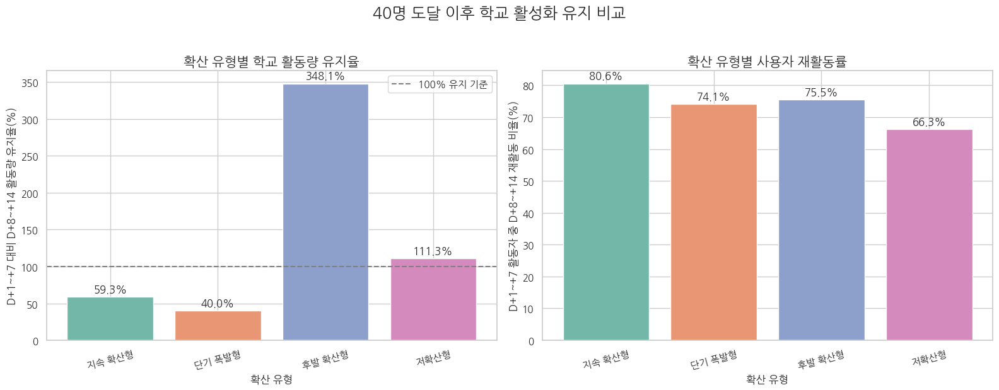

In [ ]:
# 학교 활동량·사용자 재활동 차트
cs_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
cs_colors = ['#72B7A8', '#E99675', '#8DA0CB', '#D58ABD']
cs_volume_plot = cs_type_volume_retention.copy()
cs_user_plot = cs_type_user_retention.copy()
cs_volume_plot['확산유형'] = cs_volume_plot['확산유형'].astype(str)
cs_user_plot['확산유형'] = cs_user_plot['확산유형'].astype(str)
cs_volume_plot['확산유형'] = pd.Categorical(cs_volume_plot['확산유형'], categories=cs_type_order, ordered=True)
cs_user_plot['확산유형'] = pd.Categorical(cs_user_plot['확산유형'], categories=cs_type_order, ordered=True)
cs_volume_plot = cs_volume_plot.sort_values('확산유형')
cs_user_plot = cs_user_plot.sort_values('확산유형')
cs_fig, cs_axes = plt.subplots(1, 2, figsize=(16, 6))
cs_bars1 = cs_axes[0].bar(cs_volume_plot['확산유형'], cs_volume_plot['전체활동량유지율(%)'], color=cs_colors)
cs_axes[0].axhline(100, color='gray', linestyle='--', linewidth=1.5, label='100% 유지 기준')
cs_axes[0].set_title('확산 유형별 학교 활동량 유지율', fontsize=15)
cs_axes[0].set_xlabel('확산 유형')
cs_axes[0].set_ylabel('D+1~+7 대비 D+8~+14 활동량 유지율(%)')
cs_axes[0].tick_params(axis='x', rotation=15)
cs_axes[0].legend()
cs_axes[0].bar_label(cs_bars1, fmt='%.1f%%', padding=3)
cs_bars2 = cs_axes[1].bar(cs_user_plot['확산유형'], cs_user_plot['전체사용자재활동률(%)'], color=cs_colors)
cs_axes[1].set_title('확산 유형별 사용자 재활동률', fontsize=15)
cs_axes[1].set_xlabel('확산 유형')
cs_axes[1].set_ylabel('D+1~+7 활동자 중 D+8~+14 재활동 비율(%)')
cs_axes[1].tick_params(axis='x', rotation=15)
cs_axes[1].bar_label(cs_bars2, fmt='%.1f%%', padding=3)
cs_fig.suptitle('40명 도달 이후 학교 활성화 유지 비교', fontsize=18, y=1.03)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 지속 확산형은 총활동량이 첫째 주의 약 59%로 줄었지만, 첫째 주 활동자의 약 81%는 둘째 주에도 기록이 있었다. 활동량 감소와 사용자 재활동 감소를 같은 값으로 볼 수 없다는 점이 드러난다.


### 3-7-4. 기능 범위를 맞춘 비교

- 질문·투표·하트 기록이 10개 학교에 한정돼 있어 출석·Ping 기준과 출석 단독 기준을 별도로 비교했다.
- 출석은 2023년 5월 27일부터 관측되므로 학교별 D0와 수집 시작일의 차이를 기능 개방 효과로 해석하지 않는다.


In [ ]:
# 학교별 기능 관측 범위
cs_week1_label = '도달 직후 D+1~+7'
cs_week2_label = '도달 후기 D+8~+14'
cs_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
cs_feature_columns = {'출석': 'attendance_record_count', '질문 생성': 'db_question_set_created_count', '투표 참여': 'db_vote_record_created_count', 'Ping 수신': 'db_ping_received_record_count', 'Ping 읽기': 'ping_current_read_record_count', 'Ping 답변': 'ping_current_answered_record_count', '포인트 획득': 'point_earn_event_count', '포인트 사용': 'point_spend_event_count'}
cs_available_features = {cs_feature_name: cs_column_name for cs_feature_name, cs_column_name in cs_feature_columns.items() if cs_column_name in cs_activity_analysis.columns}
print('[커버리지 점검 대상 기능]')
for cs_feature_name, cs_column_name in cs_available_features.items():
    print(f'- {cs_feature_name}: {cs_column_name}')
cs_coverage_source = cs_activity_analysis.loc[cs_activity_analysis['기간'].isin([cs_week1_label, cs_week2_label]), ['school_id', '확산유형', '기간'] + list(cs_available_features.values())].copy()
cs_school_feature_period = cs_coverage_source.groupby(['school_id', '확산유형', '기간'], observed=True)[list(cs_available_features.values())].sum().reset_index()
cs_all_school_periods = cs_all_analysis_schools[['school_id', '확산유형']].drop_duplicates().merge(pd.DataFrame({'기간': [cs_week1_label, cs_week2_label]}), how='cross')
cs_school_feature_period_full = cs_all_school_periods.merge(cs_school_feature_period, on=['school_id', '확산유형', '기간'], how='left')
cs_feature_raw_columns = list(cs_available_features.values())
cs_school_feature_period_full[cs_feature_raw_columns] = cs_school_feature_period_full[cs_feature_raw_columns].fillna(0)
cs_coverage_results = []
for cs_feature_name, cs_column_name in cs_available_features.items():
    for cs_diffusion_type in cs_type_order:
        for cs_period in [cs_week1_label, cs_week2_label]:
            cs_subset = cs_school_feature_period_full[(cs_school_feature_period_full['확산유형'] == cs_diffusion_type) & (cs_school_feature_period_full['기간'] == cs_period)]
            cs_total_schools = cs_subset['school_id'].nunique()
            cs_observed_schools = cs_subset.loc[cs_subset[cs_column_name] > 0, 'school_id'].nunique()
            cs_coverage_rate = cs_observed_schools / cs_total_schools * 100 if cs_total_schools > 0 else np.nan
            cs_coverage_results.append({'확산유형': cs_diffusion_type, '기간': cs_period, '기능': cs_feature_name, '전체학교수': cs_total_schools, '활동관찰학교수': cs_observed_schools, '활동관찰학교비율(%)': cs_coverage_rate, '총활동건수': cs_subset[cs_column_name].sum()})
cs_feature_coverage = pd.DataFrame(cs_coverage_results)
cs_feature_coverage['활동관찰학교비율(%)'] = cs_feature_coverage['활동관찰학교비율(%)'].round(2)
cs_feature_coverage['총활동건수'] = cs_feature_coverage['총활동건수'].round(0).astype('int64')
cs_overall_coverage_results = []
for cs_feature_name, cs_column_name in cs_available_features.items():
    for cs_period in [cs_week1_label, cs_week2_label]:
        cs_subset = cs_school_feature_period_full[cs_school_feature_period_full['기간'] == cs_period]
        cs_total_schools = cs_subset['school_id'].nunique()
        cs_observed_schools = cs_subset.loc[cs_subset[cs_column_name] > 0, 'school_id'].nunique()
        cs_overall_coverage_results.append({'기간': cs_period, '기능': cs_feature_name, '전체학교수': cs_total_schools, '활동관찰학교수': cs_observed_schools, '활동관찰학교비율(%)': cs_observed_schools / cs_total_schools * 100 if cs_total_schools > 0 else np.nan, '총활동건수': cs_subset[cs_column_name].sum()})
cs_overall_feature_coverage = pd.DataFrame(cs_overall_coverage_results)
cs_overall_feature_coverage['활동관찰학교비율(%)'] = cs_overall_feature_coverage['활동관찰학교비율(%)'].round(2)
cs_overall_feature_coverage['총활동건수'] = cs_overall_feature_coverage['총활동건수'].round(0).astype('int64')
print('\n[전체 학교 기준 기능별 커버리지]')
display(cs_overall_feature_coverage)
print('\n[확산 유형별 기능 커버리지]')
display(cs_feature_coverage)
cs_coverage_pivot = cs_feature_coverage.pivot_table(index=['확산유형', '기능'], columns='기간', values='활동관찰학교비율(%)', observed=True).reset_index()
cs_coverage_pivot = cs_coverage_pivot.rename(columns={cs_week1_label: 'D1_7_관찰학교비율(%)', cs_week2_label: 'D8_14_관찰학교비율(%)'})
print('\n[기능별·기간별 관찰 학교 비율]')
display(cs_coverage_pivot)
plt.close('all')
_t7tc_collected = gc.collect()


[커버리지 점검 대상 기능]
- 출석: attendance_record_count
- 질문 생성: db_question_set_created_count
- 투표 참여: db_vote_record_created_count
- Ping 수신: db_ping_received_record_count
- Ping 읽기: ping_current_read_record_count
- Ping 답변: ping_current_answered_record_count
- 포인트 획득: point_earn_event_count
- 포인트 사용: point_spend_event_count

[전체 학교 기준 기능별 커버리지]


,기간,기능,전체학교수,활동관찰학교수,활동관찰학교비율(%),총활동건수
0,도달 직후 D+1~+7,출석,3795,806,21.24,107104
1,도달 후기 D+8~+14,출석,3795,1751,46.14,253304
2,도달 직후 D+1~+7,질문 생성,3795,10,0.26,84357
3,도달 후기 D+8~+14,질문 생성,3795,10,0.26,41792
4,도달 직후 D+1~+7,투표 참여,3795,10,0.26,644193
5,도달 후기 D+8~+14,투표 참여,3795,10,0.26,331870
6,도달 직후 D+1~+7,Ping 수신,3795,683,18.00,649030
7,도달 후기 D+8~+14,Ping 수신,3795,784,20.66,321869
8,도달 직후 D+1~+7,Ping 읽기,3795,606,15.97,374333
9,도달 후기 D+8~+14,Ping 읽기,3795,640,16.86,180698



[확산 유형별 기능 커버리지]


,확산유형,기간,기능,전체학교수,활동관찰학교수,활동관찰학교비율(%),총활동건수
0,지속 확산형,도달 직후 D+1~+7,출석,1382,70,5.07,9349
1,지속 확산형,도달 후기 D+8~+14,출석,1382,442,31.98,85868
2,단기 폭발형,도달 직후 D+1~+7,출석,540,144,26.67,26321
3,단기 폭발형,도달 후기 D+8~+14,출석,540,261,48.33,59201
4,후발 확산형,도달 직후 D+1~+7,출석,586,65,11.09,6809
5,후발 확산형,도달 후기 D+8~+14,출석,586,278,47.44,29839
6,저확산형,도달 직후 D+1~+7,출석,1287,527,40.95,64625
7,저확산형,도달 후기 D+8~+14,출석,1287,770,59.83,78396
8,지속 확산형,도달 직후 D+1~+7,질문 생성,1382,9,0.65,76750
9,지속 확산형,도달 후기 D+8~+14,질문 생성,1382,9,0.65,40545



[기능별·기간별 관찰 학교 비율]


기간,확산유형,기능,D1_7_관찰학교비율(%),D8_14_관찰학교비율(%)
0,단기 폭발형,Ping 답변,9.07,6.48
1,단기 폭발형,Ping 수신,20.00,19.26
2,단기 폭발형,Ping 읽기,17.96,15.00
3,단기 폭발형,질문 생성,0.19,0.19
4,단기 폭발형,출석,26.67,48.33
5,단기 폭발형,투표 참여,0.19,0.19
6,단기 폭발형,포인트 사용,0.19,0.19
7,단기 폭발형,포인트 획득,0.19,0.19
8,저확산형,Ping 답변,5.91,3.96
9,저확산형,Ping 수신,12.90,11.89


- 3,795개 학교 중 질문 생성과 투표, 하트 기록이 있는 곳은 10개교에 집중돼 있다. 전국 학교의 기록을 합칠 때 이 기능의 수집 범위가 결과를 크게 좌우할 수 있다.


In [ ]:
# 출석·Ping 기준 활동량 비교
cs_week1_label = '도달 직후 D+1~+7'
cs_week2_label = '도달 후기 D+8~+14'
cs_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
cs_retention_features = {'출석': 'attendance_record_count', 'Ping 읽기': 'ping_current_read_record_count', 'Ping 답변': 'ping_current_answered_record_count'}
cs_feature_retention_results = []
for cs_diffusion_type in cs_type_order:
    for cs_feature_name, cs_column_name in cs_retention_features.items():
        cs_type_data = cs_school_feature_period_full[cs_school_feature_period_full['확산유형'] == cs_diffusion_type]
        cs_week1_data = cs_type_data[cs_type_data['기간'] == cs_week1_label]
        cs_week2_data = cs_type_data[cs_type_data['기간'] == cs_week2_label]
        cs_total_schools = cs_type_data['school_id'].nunique()
        if cs_total_schools == 0:
            continue
        cs_week1_volume = cs_week1_data[cs_column_name].sum()
        cs_week2_volume = cs_week2_data[cs_column_name].sum()
        cs_week1_active_schools = cs_week1_data.loc[cs_week1_data[cs_column_name] > 0, 'school_id'].nunique()
        cs_week2_active_schools = cs_week2_data.loc[cs_week2_data[cs_column_name] > 0, 'school_id'].nunique()
        cs_volume_retention = cs_week2_volume / cs_week1_volume * 100 if cs_week1_volume > 0 else np.nan
        cs_feature_retention_results.append({'확산유형': cs_diffusion_type, '기능': cs_feature_name, '전체학교수': cs_total_schools, 'D1_7_활동학교수': cs_week1_active_schools, 'D8_14_활동학교수': cs_week2_active_schools, 'D1_7_활동학교비율(%)': cs_week1_active_schools / cs_total_schools * 100, 'D8_14_활동학교비율(%)': cs_week2_active_schools / cs_total_schools * 100, 'D1_7_총활동량': cs_week1_volume, 'D8_14_총활동량': cs_week2_volume, '기능활동량유지율(%)': cs_volume_retention})
cs_feature_retention_summary = pd.DataFrame(cs_feature_retention_results)
cs_percentage_columns = ['D1_7_활동학교비율(%)', 'D8_14_활동학교비율(%)', '기능활동량유지율(%)']
cs_feature_retention_summary[cs_percentage_columns] = cs_feature_retention_summary[cs_percentage_columns].round(2)
print('[출석·Ping 기능별 유지율]')
display(cs_feature_retention_summary)
plt.close('all')
_t7tc_collected = gc.collect()


[출석·Ping 기능별 유지율]


,확산유형,기능,전체학교수,D1_7_활동학교수,D8_14_활동학교수,D1_7_활동학교비율(%),D8_14_활동학교비율(%),D1_7_총활동량,D8_14_총활동량,기능활동량유지율(%)
0,지속 확산형,출석,1382,70,442,5.07,31.98,9349,85868,918.47
1,지속 확산형,Ping 읽기,1382,295,345,21.35,24.96,332835,172616,51.86
2,지속 확산형,Ping 답변,1382,180,193,13.02,13.97,63120,33570,53.18
3,단기 폭발형,출석,540,144,261,26.67,48.33,26321,59201,224.92
4,단기 폭발형,Ping 읽기,540,97,81,17.96,15.00,33017,5144,15.58
5,단기 폭발형,Ping 답변,540,49,35,9.07,6.48,5338,772,14.46
6,후발 확산형,출석,586,65,278,11.09,47.44,6809,29839,438.23
7,후발 확산형,Ping 읽기,586,74,96,12.63,16.38,1847,1310,70.93
8,후발 확산형,Ping 답변,586,39,41,6.66,7.00,355,217,61.13
9,저확산형,출석,1287,527,770,40.95,59.83,64625,78396,121.31


- 네 유형 모두 둘째 주 출석 건수는 늘고, Ping 최종 읽기·답장 상태가 연결된 기록은 줄었다. 지속 확산형의 출석은 약 9.2배인 반면 Ping 읽기 상태 기록은 첫째 주의 51.9%다.

- 출석 자료의 시작일과 Ping 상태의 시점 한계가 서로 달라, 이 차이를 곧 사용 기능의 이동으로 볼 수는 없다.


In [ ]:
# 출석·Ping 사용자 재활동
cs_core_action_columns = ['attendance_record_count', 'ping_current_read_record_count', 'ping_current_answered_record_count']
cs_core_activity_source = cs_activity_analysis.loc[cs_activity_analysis['기간'].isin([cs_week1_label, cs_week2_label]), ['school_id', '확산유형', 'user_id', '기간'] + cs_core_action_columns].copy()
cs_core_activity_source['핵심활동여부'] = (cs_core_activity_source[cs_core_action_columns].sum(axis=1) > 0).astype(int)
cs_core_week1_users = cs_core_activity_source.loc[(cs_core_activity_source['기간'] == cs_week1_label) & (cs_core_activity_source['핵심활동여부'] == 1), ['school_id', '확산유형', 'user_id']].drop_duplicates()
cs_core_week2_users = cs_core_activity_source.loc[(cs_core_activity_source['기간'] == cs_week2_label) & (cs_core_activity_source['핵심활동여부'] == 1), ['school_id', 'user_id']].drop_duplicates()
print('D+1~+7 출석·Ping 활동 사용자:', f'{len(cs_core_week1_users):,}명')
print('D+8~+14 출석·Ping 활동 사용자:', f'{len(cs_core_week2_users):,}명')
cs_core_reactivated_users = cs_core_week1_users.merge(cs_core_week2_users.assign(재활동여부=1), on=['school_id', 'user_id'], how='left', validate='one_to_one')
cs_core_reactivated_users['재활동여부'] = cs_core_reactivated_users['재활동여부'].fillna(0).astype(int)
cs_core_user_retention_summary = cs_core_reactivated_users.groupby('확산유형', observed=True).agg(D1_7_활동사용자수=('user_id', 'nunique'), 두기간모두활동사용자수=('재활동여부', 'sum')).reset_index()
cs_week2_type_users = cs_core_week2_users.merge(cs_all_analysis_schools[['school_id', '확산유형']].drop_duplicates(), on='school_id', how='left', validate='many_to_one').groupby('확산유형', observed=True)['user_id'].nunique().reset_index(name='D8_14_활동사용자수')
cs_core_user_retention_summary = cs_core_user_retention_summary.merge(cs_week2_type_users, on='확산유형', how='outer')
cs_core_user_retention_summary[['D1_7_활동사용자수', 'D8_14_활동사용자수', '두기간모두활동사용자수']] = cs_core_user_retention_summary[['D1_7_활동사용자수', 'D8_14_활동사용자수', '두기간모두활동사용자수']].fillna(0).astype(int)
cs_core_user_retention_summary['출석Ping_사용자재활동률(%)'] = np.where(cs_core_user_retention_summary['D1_7_활동사용자수'] > 0, cs_core_user_retention_summary['두기간모두활동사용자수'] / cs_core_user_retention_summary['D1_7_활동사용자수'] * 100, np.nan)
cs_core_user_retention_summary['출석Ping_사용자재활동률(%)'] = cs_core_user_retention_summary['출석Ping_사용자재활동률(%)'].round(2)
cs_core_user_retention_summary['확산유형'] = pd.Categorical(cs_core_user_retention_summary['확산유형'], categories=cs_type_order, ordered=True)
cs_core_user_retention_summary = cs_core_user_retention_summary.sort_values('확산유형').reset_index(drop=True)
print('\n[출석·Ping 기준 사용자 재활동률]')
display(cs_core_user_retention_summary)
del cs_core_activity_source
del cs_core_week1_users
del cs_core_week2_users
del cs_core_reactivated_users
plt.close('all')
_t7tc_collected = gc.collect()


D+1~+7 출석·Ping 활동 사용자: 53,025명
D+8~+14 출석·Ping 활동 사용자: 101,070명

[출석·Ping 기준 사용자 재활동률]


,확산유형,D1_7_활동사용자수,두기간모두활동사용자수,D8_14_활동사용자수,출석Ping_사용자재활동률(%)
0,지속 확산형,12645,9957,42350,78.74
1,단기 폭발형,13500,9906,20809,73.38
2,후발 확산형,3123,2359,12186,75.54
3,저확산형,23757,15751,25725,66.30


- 출석·Ping 기준 재활동률은 지속 확산형 78.74%, 후발 확산형 75.54%, 단기 폭발형 73.38%, 저확산형 66.30%다. 기능을 좁혀도 유형의 순서는 유지됐다.


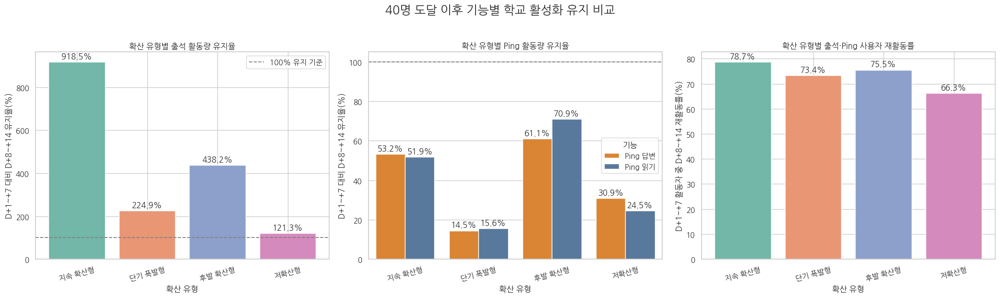

In [ ]:
# 기능 범위 보정 후 비교 차트
cs_type_order = ['지속 확산형', '단기 폭발형', '후발 확산형', '저확산형']
cs_colors = {'지속 확산형': '#72B7A8', '단기 폭발형': '#E99675', '후발 확산형': '#8DA0CB', '저확산형': '#D58ABD'}
cs_feature_plot = cs_feature_retention_summary.copy()
cs_user_plot = cs_core_user_retention_summary.copy()
cs_feature_plot['확산유형'] = cs_feature_plot['확산유형'].astype(str)
cs_user_plot['확산유형'] = cs_user_plot['확산유형'].astype(str)
cs_feature_plot['확산유형'] = pd.Categorical(cs_feature_plot['확산유형'], categories=cs_type_order, ordered=True)
cs_user_plot['확산유형'] = pd.Categorical(cs_user_plot['확산유형'], categories=cs_type_order, ordered=True)
cs_attendance_plot = cs_feature_plot[cs_feature_plot['기능'] == '출석'].sort_values('확산유형')
cs_ping_plot = cs_feature_plot[cs_feature_plot['기능'].isin(['Ping 읽기', 'Ping 답변'])].sort_values(['확산유형', '기능'])
cs_user_plot = cs_user_plot.sort_values('확산유형')
cs_fig, cs_axes = plt.subplots(1, 3, figsize=(21, 6))
cs_bars1 = cs_axes[0].bar(cs_attendance_plot['확산유형'], cs_attendance_plot['기능활동량유지율(%)'], color=[cs_colors[str(cs_x)] for cs_x in cs_attendance_plot['확산유형']])
cs_axes[0].axhline(100, color='gray', linestyle='--', linewidth=1.3, label='100% 유지 기준')
cs_axes[0].set_title('확산 유형별 출석 활동량 유지율')
cs_axes[0].set_xlabel('확산 유형')
cs_axes[0].set_ylabel('D+1~+7 대비 D+8~+14 유지율(%)')
cs_axes[0].tick_params(axis='x', rotation=15)
cs_axes[0].legend()
cs_axes[0].bar_label(cs_bars1, fmt='%.1f%%', padding=3)
sns.barplot(data=cs_ping_plot, x='확산유형', y='기능활동량유지율(%)', hue='기능', ax=cs_axes[1], palette={'Ping 읽기': '#4C78A8', 'Ping 답변': '#F58518'})
cs_axes[1].axhline(100, color='gray', linestyle='--', linewidth=1.3)
cs_axes[1].set_title('확산 유형별 Ping 활동량 유지율')
cs_axes[1].set_xlabel('확산 유형')
cs_axes[1].set_ylabel('D+1~+7 대비 D+8~+14 유지율(%)')
cs_axes[1].tick_params(axis='x', rotation=15)
cs_axes[1].legend(title='기능')
for cs_container in cs_axes[1].containers:
    cs_axes[1].bar_label(cs_container, fmt='%.1f%%', padding=3)
cs_bars3 = cs_axes[2].bar(cs_user_plot['확산유형'], cs_user_plot['출석Ping_사용자재활동률(%)'], color=[cs_colors[str(cs_x)] for cs_x in cs_user_plot['확산유형']])
cs_axes[2].set_title('확산 유형별 출석·Ping 사용자 재활동률')
cs_axes[2].set_xlabel('확산 유형')
cs_axes[2].set_ylabel('D+1~+7 활동자 중 D+8~+14 재활동률(%)')
cs_axes[2].tick_params(axis='x', rotation=15)
cs_axes[2].bar_label(cs_bars3, fmt='%.1f%%', padding=3)
cs_fig.suptitle('40명 도달 이후 기능별 학교 활성화 유지 비교', fontsize=18, y=1.03)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- 활동 범위를 출석·Ping으로 좁히면 지속 확산형의 재활동률은 80.56%에서 78.74%로 낮아진다. 저확산형·후발 확산형은 변하지 않았다.


In [ ]:
# 출석 단독 재활동
cs_attendance_source = cs_activity_analysis.loc[cs_activity_analysis['attendance_record_count'].gt(0), ['school_id', 'user_id', '확산유형', '기간']].drop_duplicates()
cs_a1 = cs_attendance_source[cs_attendance_source['기간'].eq(cs_week1_label)][['school_id', 'user_id', '확산유형']].drop_duplicates()
cs_a2 = cs_attendance_source[cs_attendance_source['기간'].eq(cs_week2_label)][['school_id', 'user_id']].drop_duplicates()
cs_attendance_cohort = cs_a1.merge(cs_a2.assign(returned=1), on=['school_id', 'user_id'], how='left', validate='one_to_one')
cs_attendance_cohort['returned'] = cs_attendance_cohort['returned'].fillna(0)
cs_attendance_retention = cs_attendance_cohort.groupby('확산유형', observed=True).agg(첫째주출석사용자수=('user_id', 'nunique'), 두기간출석사용자수=('returned', 'sum')).reset_index()
cs_attendance_retention['출석기준재활동률(%)'] = (cs_attendance_retention['두기간출석사용자수'] / cs_attendance_retention['첫째주출석사용자수'] * 100).round(2)
display(cs_attendance_retention)
print('출석 기록 기준입니다. 앱 전체 방문 리텐션과 구분하세요.')
plt.close('all')
_t7tc_collected = gc.collect()


,확산유형,첫째주출석사용자수,두기간출석사용자수,출석기준재활동률(%)
0,단기 폭발형,12416,"9,244.00",74.45
1,저확산형,23148,"15,447.00",66.73
2,지속 확산형,5350,"4,526.00",84.60
3,후발 확산형,2872,"2,231.00",77.68


출석 기록 기준입니다. 앱 전체 방문 리텐션과 구분하세요.


- 출석만 남기면 지속 확산형의 재활동률이 84.60%로 가장 높다. 후발 확산형 77.68%, 단기 폭발형 74.45%, 저확산형 66.73% 순이다.

- 출석 기록을 다시 남긴 비율이며 출석 없이 방문한 사용자는 잡히지 않는다.


In [ ]:
# 학교별 Continuation 결과·변수 정리
continuation_school_results = {name: globals().get('cs_' + name) for name in ['type_volume_retention', 'type_user_retention', 'feature_retention_summary', 'attendance_retention']}
t7tc_release('cs_')


파트 임시 데이터 메모리 정리 완료: cs_


### 3-7-5. 가입 코호트와 관측 범위

- 가입일 이후 활동을 연결하기 전 입력 기간과 가입 이전 기록을 점검했다.
- DB 행동과 Hackle 방문은 수집 구간이 달라 별도로 분석했다.


In [ ]:
# 후속 행동 분석 입력·설정
cf_SRC = T7TC_PROCESSED
t7tc_style()
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda cf_x: f'{cf_x:,.4f}')

def cf_path(cf_key):
    return t7tc_clean_path(cf_key)

def cf_read(cf_key, cf_cols=None):
    return t7tc_follow_read(cf_key, cf_cols)

def cf_save(cf_df, cf_name):
    return cf_df

def cf_show(cf_text):
    display(Markdown(cf_text))

def cf_wilson(cf_k, cf_n):
    if not cf_n:
        return (np.nan, np.nan)
    cf_z = 1.96
    cf_p = cf_k / cf_n
    cf_den = 1 + cf_z * cf_z / cf_n
    cf_mid = (cf_p + cf_z * cf_z / (2 * cf_n)) / cf_den
    cf_half = cf_z * np.sqrt(cf_p * (1 - cf_p) / cf_n + cf_z * cf_z / (4 * cf_n * cf_n)) / cf_den
    return (cf_mid - cf_half, cf_mid + cf_half)

def cf_rate_row(cf_label, cf_x):
    cf_n = len(cf_x)
    cf_k = int(cf_x.sum())
    cf_low, cf_high = cf_wilson(cf_k, cf_n)
    return dict(group=cf_label, n=cf_n, active=cf_k, rate=cf_k / cf_n if cf_n else np.nan, ci_low=cf_low, ci_high=cf_high)
cf_manifest = pd.DataFrame([{'file': str(cf_f.relative_to(cf_SRC)), 'bytes': cf_f.stat().st_size, 'modified_at': pd.Timestamp(cf_f.stat().st_mtime, unit='s').isoformat()} for cf_f in cf_SRC.rglob('*.csv*') if cf_f.is_file()])
display(cf_manifest)
print('Python', platform.python_version(), 'pandas', pd.__version__)
print('입력:', cf_SRC)
plt.close('all')
_t7tc_collected = gc.collect()


,file,bytes,modified_at
0,lifecycle_safety_attendance/mart_safety_event_...,1718068,2026-10-01T04:12:31.423085690
1,lifecycle_safety_attendance/mart_lifecycle_eve...,7470358,2026-10-01T04:13:18.634262562
2,lifecycle_safety_attendance/mart_safety_event_...,1520470,2026-10-01T04:14:04.286268234
3,lifecycle_safety_attendance/mart_promo_event_r...,6305,2026-10-01T04:13:20.853506088
4,lifecycle_safety_attendance/mart_attendance_re...,6750249,2026-10-01T04:15:23.880995512
5,lifecycle_safety_attendance/bridge_attendance_...,23167373,2026-10-01T04:15:18.043355465
6,question_candidate/mart_question_set_record_v2...,9007668,2026-10-01T04:04:41.608566761
7,question_candidate/mart_question_exposure_clea...,64276826,2026-10-01T03:50:29.959172487
8,question_candidate/mart_question_piece_record_...,42451871,2026-10-01T04:06:44.302021027
9,question_candidate/mart_vote_record_v2_clean.c...,38642279,2026-10-01T04:07:40.174147844


Python 3.13.15 pandas 2.2.3
입력: /content/team7_processed


- 후기 행동 분석 입력 파일과 관측 범위를 확인했다.


In [ ]:
# 사용자 코호트·기록 유효성
cf_profile = cf_read('mart_user_acquisition_profile_v2', ['user_id', 'signup_at', 'is_staff', 'is_superuser', 'current_school_id', 'current_school_type', 'current_grade'])
assert cf_profile.user_id.is_unique
cf_profile['signup_at'] = pd.to_datetime(cf_profile.signup_at, format='mixed', errors='coerce')
cf_normal = ~cf_profile.is_staff.astype(str).str.lower().isin(['1', 'true']) & ~cf_profile.is_superuser.astype(str).str.lower().isin(['1', 'true'])
cf_users = cf_profile.loc[cf_normal & cf_profile.signup_at.notna()].copy().set_index('user_id')
cf_users['signup_date'] = cf_users.signup_at.dt.normalize()
cf_users['cohort'] = cf_users.signup_at.dt.strftime('%Y-%m')
cf_users['signup_week'] = cf_users.signup_date.dt.to_period('W-SUN').astype(str)
display(cf_save(pd.DataFrame({'항목': ['프로필 전체', '직원·관리자 제외', '가입시각 결측', '최종 모집단'], '명': [len(cf_profile), int((~cf_normal).sum()), int((cf_normal & cf_profile.signup_at.isna()).sum()), len(cf_users)]}), '01_population'))
cf_counts = {'sent': 'friend_request_sent_count', 'received': 'friend_request_received_count', 'attendance': 'attendance_record_count', 'question': 'db_question_set_created_count', 'vote': 'db_vote_record_created_count', 'ping_received': 'db_ping_received_record_count', 'payment': 'db_payment_success_count', 'hackle': 'hackle_event_count'}
cf_flags = ['friend_request_source_range_flag', 'attendance_source_range_flag', 'question_db_source_range_flag', 'value_db_source_range_flag', 'hackle_24d_source_range_flag']
cf_parts = []
cf_daily_parts = []
cf_range_parts = []
cf_audit = {'raw_rows': 0, 'missing_profile_rows': 0, 'pre_signup_rows': 0, 'bad_date_rows': 0}
cf_cols = ['user_id', 'activity_date'] + list(cf_counts.values()) + cf_flags
for cf_chunk in pd.read_csv(cf_path('mart_user_activity_daily_v2'), usecols=cf_cols, chunksize=400000, na_values=['\\N']):
    cf_audit['raw_rows'] += len(cf_chunk)
    cf_chunk['date'] = pd.to_datetime(cf_chunk.activity_date, errors='coerce')
    cf_audit['bad_date_rows'] += int(cf_chunk.date.isna().sum())
    for cf_flag in cf_flags:
        cf_dates = cf_chunk.loc[cf_chunk[cf_flag].eq(1), 'date']
        if len(cf_dates):
            cf_range_parts.append((cf_flag, cf_dates.min(), cf_dates.max()))
    cf_audit['missing_profile_rows'] += int((~cf_chunk.user_id.isin(cf_users.index)).sum())
    cf_c = cf_chunk[cf_chunk.user_id.isin(cf_users.index) & cf_chunk.date.notna()].copy()
    cf_c['age'] = (cf_c.date - cf_c.user_id.map(cf_users.signup_date)).dt.days
    cf_audit['pre_signup_rows'] += int(cf_c.age.lt(0).sum())
    cf_c = cf_c[cf_c.age.ge(0)]
    cf_small = cf_c[['user_id', 'date', 'age']].copy()
    for cf_label, cf_col in cf_counts.items():
        cf_small[cf_label] = cf_c[cf_col].fillna(0).gt(0)
    cf_daily_parts.append(cf_small.groupby('date')[list(cf_counts)].sum())
    cf_small['user_id'] = cf_small.user_id.astype('int64')
    cf_small['age'] = cf_small.age.astype('int16')
    cf_parts.append(cf_small)
    print('.', end='')
cf_a = pd.concat(cf_parts, ignore_index=True)
del cf_parts, cf_chunk, cf_c, cf_small
gc.collect()
assert not cf_a.duplicated(['user_id', 'date']).any(), '사용자-날짜 중복은 집계 전 원인 확인 필요'
cf_a['core'] = cf_a.sent | cf_a.payment
cf_a['extended'] = cf_a.core | cf_a.attendance
cf_a['question_active'] = cf_a.question | cf_a.vote
cf_coverage = pd.DataFrame(cf_range_parts, columns=['source', 'start', 'end']).groupby('source').agg(start=('start', 'min'), end=('end', 'max'))
cf_daily = pd.concat(cf_daily_parts).groupby(level=0).sum().sort_index()
display(cf_save(cf_coverage.reset_index(), '02_source_bounds'))
display(pd.Series(cf_audit, name='rows'))
cf_actual = []
for cf_kind in cf_counts:
    cf_x = cf_a[cf_a[cf_kind]]
    cf_actual.append({'behavior': cf_kind, 'first_record_date': cf_x.date.min(), 'last_record_date': cf_x.date.max(), 'user_days': len(cf_x), 'users': cf_x.user_id.nunique()})
display(cf_save(pd.DataFrame(cf_actual), '02_actual_behavior_bounds'))
cf_save(pd.DataFrame([cf_audit]), '02_daily_audit')
cf_save(cf_daily.reset_index(), '02_daily_source_users')
plt.close('all')
_t7tc_collected = gc.collect()


,항목,명
0,프로필 전체,677085
1,직원·관리자 제외,4
2,가입시각 결측,0
3,최종 모집단,677081


.....................

,source,start,end
0,attendance_source_range_flag,2023-05-27,2024-05-09
1,friend_request_source_range_flag,2023-04-17,2024-05-09
2,hackle_24d_source_range_flag,2023-07-18,2023-08-10
3,question_db_source_range_flag,2023-04-28,2024-05-07
4,value_db_source_range_flag,2023-04-28,2024-05-08


,rows
raw_rows,8224667
missing_profile_rows,4
pre_signup_rows,43
bad_date_rows,0


,behavior,first_record_date,last_record_date,user_days,users
0,sent,2023-04-17,2024-05-09,1835908,649072
1,received,2023-04-17,2024-05-09,5385086,660841
2,attendance,2023-05-27,2024-05-09,2222327,328692
3,question,2023-04-28,2024-05-07,49571,4972
4,vote,2023-04-28,2024-05-08,50974,4849
5,ping_received,2023-04-28,2024-05-08,175510,15426
6,payment,2023-05-13,2024-05-08,75719,59192
7,hackle,2023-07-18,2023-08-10,418071,140663


- 일별 자료 8,224,667행 중 프로필 미연결 4행·가입 이전 43행을 제외했다. 잘못된 날짜는 없었다.


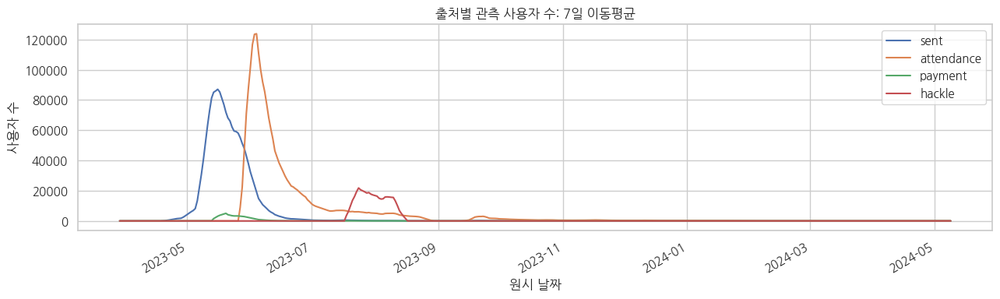

,source,start,end,days
3,attendance,2023-08-28,2023-09-11,15
60,question,2024-04-01,2024-04-11,11
59,question,2024-03-20,2024-03-29,10
65,question,2024-04-23,2024-05-02,10
54,question,2024-02-10,2024-02-18,9
58,question,2024-03-11,2024-03-16,6
55,question,2024-02-21,2024-02-26,6
13,payment,2024-03-03,2024-03-07,5
57,question,2024-03-04,2024-03-07,4
38,question,2023-11-24,2023-11-27,4


출석 공백에는 기능 중단과 수집 누락이 섞일 수 있다. Hackle 기록이 늘어난 구간도 서비스 회복으로 단정하기 어렵다.

In [ ]:
# 출처별 날짜 공백·관측 범위
cf_fig, cf_ax = plt.subplots(figsize=(13, 4))
cf_daily[['sent', 'attendance', 'payment', 'hackle']].rolling(7, min_periods=1).mean().plot(ax=cf_ax)
cf_ax.set(title='출처별 관측 사용자 수: 7일 이동평균', ylabel='사용자 수', xlabel='원시 날짜')
plt.tight_layout()
plt.show()
cf_calendar = pd.date_range(cf_daily.index.min(), cf_daily.index.max())
cf_gap_rows = []
for cf_col in ['sent', 'attendance', 'payment', 'question', 'hackle']:
    cf_series = cf_daily[cf_col].reindex(cf_calendar, fill_value=0)
    cf_nonzero = cf_series[cf_series.gt(0)]
    cf_zero = cf_series.loc[cf_nonzero.index.min():cf_nonzero.index.max()].eq(0)
    for cf__, cf_g in cf_zero.groupby(cf_zero.ne(cf_zero.shift()).cumsum()):
        if cf_g.iloc[0]:
            cf_gap_rows.append({'source': cf_col, 'start': cf_g.index.min(), 'end': cf_g.index.max(), 'days': len(cf_g)})
cf_gaps = pd.DataFrame(cf_gap_rows, columns=['source', 'start', 'end', 'days'])
display(cf_save(cf_gaps, '03_internal_zero_days').sort_values('days', ascending=False).head(20))
cf_show('출석 공백에는 기능 중단과 수집 누락이 섞일 수 있다. Hackle 기록이 늘어난 구간도 서비스 회복으로 단정하기 어렵다.')
plt.close('all')
_t7tc_collected = gc.collect()


- Hackle은 2023년 7월 18일~8월 10일의 24일 자료다. 출석은 5월 27일, 친구 요청은 4월 17일부터 관측된다.
- 무기록 구간에는 수집 공백이 포함될 수 있으므로 이를 모두 미활동으로 해석하지 않는다.


### 3-7-6. 5월 가입자의 후기 행동

- 공통 관측 기간을 충족하는 5월 가입자를 대상으로 D8~D30 활동과 초기 경험별 후기 활동을 비교했다.
- 핵심 DB 활동은 친구 요청 발송 또는 결제다. 출석을 포함한 확장 지표·10개교 질문 행동·Hackle 방문은 별도로 집계했다.


,group,n,active,rate,ci_low,ci_high
0,D8~D30,635505,174365,0.2744,0.2733,0.2755
1,D31~D90,635505,19727,0.0310,0.0306,0.0315
2,D91~D180,635505,3604,0.0057,0.0055,0.0059


5월 일반 가입자는 635,505명이다. 복합 지표의 공통 관측 기간은 2023-05-13~2024-05-08이며, D0~D30 비교에는 336,194명이 남는다. 앞서 가입한 299,311명은 결제 기록의 관측 범위가 불확실해 제외했다. 전체 5월 가입자 결과는 위의 친구 요청 발송 표에 담았다.

,group,n,active,rate,ci_low,ci_high,kind,mean_days,median_days_active,repeat_2days_rate
0,D8~D30,336194,81917,0.2437,0.2422,0.2451,core,0.4195,1.0000,0.0947
1,D8~D30,336194,180159,0.5359,0.5342,0.5376,extended,2.7685,3.0000,0.3998
2,D31~D90,336194,8509,0.0253,0.0248,0.0258,core,0.0322,1.0000,0.0042
3,D31~D90,336194,56123,0.1669,0.1657,0.1682,extended,0.7186,2.0000,0.0904
4,D91~D180,336194,2100,0.0062,0.0060,0.0065,core,0.0071,1.0000,0.0006
5,D91~D180,336194,16166,0.0481,0.0474,0.0488,extended,0.1276,1.0000,0.0177
6,D181~D270,336194,699,0.0021,0.0019,0.0022,core,0.0022,1.0000,0.0001
7,D181~D270,336194,4743,0.0141,0.0137,0.0145,extended,0.0347,1.0000,0.0033
8,D271~D360,76854,41,0.0005,0.0004,0.0007,core,0.0006,1.0000,0.0000
9,D271~D360,76854,312,0.0041,0.0036,0.0045,extended,0.0064,1.0000,0.0007


,group,n,active,rate,ci_low,ci_high
0,2023-05,336194,81917,0.2437,0.2422,0.2451
1,2023-06,16737,1920,0.1147,0.1100,0.1196
2,2023-07,1849,112,0.0606,0.0506,0.0724
3,2023-08,524,18,0.0344,0.0218,0.0536
4,2023-09,602,31,0.0515,0.0365,0.0722
5,2023-10,409,13,0.0318,0.0187,0.0536
6,2023-11,731,5,0.0068,0.0029,0.0159
7,2023-12,231,5,0.0216,0.0093,0.0497
8,2024-01,455,6,0.0132,0.0061,0.0285
9,2024-02,255,5,0.0196,0.0084,0.0451


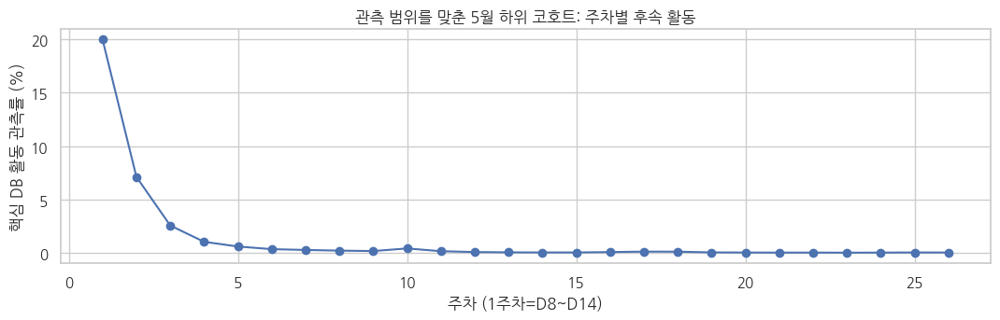

5월 하위 코호트 336,194명 중 D8~D30 핵심 DB 활동은 81,917명(24.37%)에게 있었다. 친구 요청 발송·결제 기록을 센 값이다.

In [ ]:
# 5월 가입자·D8~D30 활동
cf_core_start = max(cf_coverage.loc['friend_request_source_range_flag', 'start'], cf_a.loc[cf_a.payment, 'date'].min())
cf_core_end = min(cf_coverage.loc['friend_request_source_range_flag', 'end'], cf_a.loc[cf_a.payment, 'date'].max())

def cf_eligible(cf_base, cf_lo, cf_hi, cf_start=cf_core_start, cf_end=cf_core_end):
    return cf_base[(cf_base.signup_date + pd.Timedelta(days=cf_lo) >= cf_start) & (cf_base.signup_date + pd.Timedelta(days=cf_hi) <= cf_end)].copy()
cf_may = cf_users[cf_users.cohort.eq('2023-05')].copy()

def cf_attach_days(cf_base, cf_lo, cf_hi, cf_kind):
    cf_d = cf_a[cf_a.age.between(cf_lo, cf_hi) & cf_a[cf_kind]].groupby('user_id').size()
    return cf_base.index.to_series().map(cf_d).fillna(0).astype(int)
cf_friend_start = cf_coverage.loc['friend_request_source_range_flag', 'start']
cf_friend_end = cf_coverage.loc['friend_request_source_range_flag', 'end']
cf_allmay = []
for cf_lo, cf_hi in [(8, 30), (31, 90), (91, 180)]:
    cf_bb = cf_eligible(cf_may, 0, cf_hi, cf_friend_start, cf_friend_end)
    cf_rr = cf_rate_row(f'D{cf_lo}~D{cf_hi}', cf_attach_days(cf_bb, cf_lo, cf_hi, 'sent').gt(0))
    cf_allmay.append(cf_rr)
cf_fullmay = cf_save(pd.DataFrame(cf_allmay), '04a_full_may_friend_sent_followup')
display(cf_fullmay)
cf_show(f'5월 일반 가입자는 {len(cf_may):,}명이다. 복합 지표의 공통 관측 기간은 {cf_core_start.date()}~{cf_core_end.date()}이며, D0~D30 비교에는 {len(cf_eligible(cf_may, 0, 30)):,}명이 남는다. 앞서 가입한 {len(cf_may) - len(cf_eligible(cf_may, 0, 30)):,}명은 결제 기록의 관측 범위가 불확실해 제외했다. 전체 5월 가입자 결과는 위의 친구 요청 발송 표에 담았다.')
cf_summary = []
for cf_lo, cf_hi in [(8, 30), (31, 90), (91, 180), (181, 270), (271, 360)]:
    cf_base = cf_eligible(cf_may, 0, cf_hi)
    for cf_kind in ['core', 'extended']:
        cf_days = cf_attach_days(cf_base, cf_lo, cf_hi, cf_kind)
        cf_row = cf_rate_row(f'D{cf_lo}~D{cf_hi}', cf_days.gt(0))
        cf_row.update(kind=cf_kind, mean_days=cf_days.mean(), median_days_active=cf_days[cf_days.gt(0)].median(), repeat_2days_rate=cf_days.ge(2).mean())
        cf_summary.append(cf_row)
cf_db_summary = cf_save(pd.DataFrame(cf_summary), '04_may_followup')
display(cf_db_summary)
cf_coh = []
for cf_month, cf_base in cf_users.groupby('cohort'):
    cf_b = cf_eligible(cf_base, 0, 30)
    if len(cf_b):
        cf_coh.append(cf_rate_row(cf_month, cf_attach_days(cf_b, 8, 30, 'core').gt(0)))
cf_cohort_result = cf_save(pd.DataFrame(cf_coh), '05_monthly_cohort_d8_d30')
display(cf_cohort_result)
cf_weekly = []
for cf_w in range(1, 27):
    cf_lo = 7 * cf_w + 1
    cf_hi = cf_lo + 6
    cf_b = cf_eligible(cf_may, 0, cf_hi)
    cf_row = cf_rate_row(cf_w, cf_attach_days(cf_b, cf_lo, cf_hi, 'core').gt(0))
    cf_weekly.append(cf_row)
cf_weekly = pd.DataFrame(cf_weekly)
cf_save(cf_weekly, '06_may_equal_week_activity')
cf_fig, cf_ax = plt.subplots(figsize=(11, 3.6))
cf_ax.plot(cf_weekly.group, 100 * cf_weekly.rate, marker='o')
cf_ax.set(xlabel='주차 (1주차=D8~D14)', ylabel='핵심 DB 활동 관측률 (%)', title='관측 범위를 맞춘 5월 하위 코호트: 주차별 후속 활동')
plt.tight_layout()
plt.show()
cf_r = cf_db_summary[(cf_db_summary.group == 'D8~D30') & (cf_db_summary.kind == 'core')].iloc[0]
cf_show(f'5월 하위 코호트 {cf_r.n:,.0f}명 중 D8~D30 핵심 DB 활동은 {cf_r.active:,.0f}명({cf_r.rate:.2%})에게 있었다. 친구 요청 발송·결제 기록을 센 값이다.')
plt.close('all')
_t7tc_collected = gc.collect()


- 전체 5월 가입자는 635,505명이다. 복합 활동의 관측 범위를 맞춘 하위 코호트는 336,194명이며, 이 중 81,917명, 24.37%에게 D8~D30 핵심 DB 활동이 있었다.

- 출석을 더하면 같은 기간 관측률은 53.59%다.
- 행동 정의에 따라 차이가 크므로 24.37%를 앱 전체 재방문율로 쓰기는 어렵다.


In [ ]:
# 초기 경험별 후기 활동 비교
cf_sets = cf_read('mart_question_set_record_v2', ['question_set_owner_user_id', 'question_set_created_at', 'owner_current_school_id'])
cf_schools = cf_sets.owner_current_school_id.dropna().unique()
cf_q_start = pd.to_datetime(cf_sets.question_set_created_at, format='mixed').min().ceil('D')
cf_q_end = pd.to_datetime(cf_sets.question_set_created_at, format='mixed').max().floor('D') - pd.Timedelta(days=1)
cf_show(f'질문 데이터 소유자의 현재 학교: **{len(cf_schools)}개**. 범위는 {cf_q_start.date()}~{cf_q_end.date()}의 완전한 내부 날짜를 사용한다.')
cf_base = cf_eligible(cf_may, 0, 30)
cf_base['later'] = cf_attach_days(cf_base, 8, 30, 'core').gt(0)
cf_base['early_days'] = cf_attach_days(cf_base, 0, 7, 'core')
cf_base['activity_band'] = pd.cut(cf_base.early_days, [-1, 0, 1, 3, 8], labels=['0', '1', '2~3', '4~8']).astype(str)
for cf_feature in ['sent', 'received', 'payment', 'question', 'vote', 'ping_received']:
    cf_ids = cf_a.loc[cf_a.age.between(0, 7) & cf_a[cf_feature], 'user_id'].unique()
    cf_base[cf_feature] = cf_base.index.isin(cf_ids)
cf_s = cf_read('mart_safety_event_v2', ['source_table', 'source_row_id', 'actor_user_id', 'event_at_raw', 'is_true_event_time_flag', 'canonical_semantic_record_flag', 'feedback_domain_rule_v1'])
cf_s = cf_s[cf_s.is_true_event_time_flag.eq(1) & cf_s.canonical_semantic_record_flag.eq(1)].copy()
cf_s['date'] = pd.to_datetime(cf_s.event_at_raw, format='mixed', errors='coerce').dt.normalize()
cf_s['age'] = (cf_s.date - cf_s.actor_user_id.map(cf_users.signup_date)).dt.days
cf_base['feedback'] = cf_base.index.isin(cf_s.loc[cf_s.age.between(0, 7), 'actor_user_id'])
display(cf_save(cf_s.groupby(['source_table', 'feedback_domain_rule_v1']).agg(rows=('source_row_id', 'size'), start=('date', 'min'), end=('date', 'max')).reset_index(), '07_safety_scope'))
cf_comparisons = []
cf_adjusted = []

def cf_compare(cf_b, cf_feature, cf_label, cf_outcome='later', cf_strata=['signup_week', 'activity_band']):
    for cf_value, cf_g in cf_b.groupby(cf_feature):
        cf_row = cf_rate_row(cf_label + ' / ' + str(bool(cf_value)), cf_g[cf_outcome])
        cf_row.update(feature=cf_feature, outcome=cf_outcome)
        cf_comparisons.append(cf_row)
    cf_t = cf_b.groupby(cf_strata + [cf_feature], observed=True)[cf_outcome].agg(['size', 'mean']).unstack(cf_feature)
    if not all((cf_v in cf_t['size'].columns for cf_v in [False, True])):
        cf_adjusted.append(dict(feature=cf_feature, label=cf_label, outcome=cf_outcome, common_n=0, total_n=len(cf_b), retained=0, unexposed_rate=np.nan, exposed_rate=np.nan, difference_pp=np.nan, strata=0, status='비교군 한쪽 부재'))
        return
    cf_ok = cf_t['size'].fillna(0).min(axis=1).ge(20)
    cf_t = cf_t.loc[cf_ok]
    cf_n = cf_t['size'].sum().sum()
    if cf_n:
        cf_weight = cf_t['size'].sum(axis=1) / cf_n
        cf_p0 = (cf_t['mean'][False] * cf_weight).sum()
        cf_p1 = (cf_t['mean'][True] * cf_weight).sum()
        cf_adjusted.append(dict(feature=cf_feature, label=cf_label, outcome=cf_outcome, common_n=int(cf_n), total_n=len(cf_b), retained=cf_n / len(cf_b), unexposed_rate=cf_p0, exposed_rate=cf_p1, difference_pp=100 * (cf_p1 - cf_p0), strata=len(cf_t), status='제한적 공통지지' if cf_n / len(cf_b) < 0.5 else '공통지지 비교'))
    else:
        cf_adjusted.append(dict(feature=cf_feature, label=cf_label, outcome=cf_outcome, common_n=0, total_n=len(cf_b), retained=0, unexposed_rate=np.nan, exposed_rate=np.nan, difference_pp=np.nan, strata=0, status='양군 20명 이상 공통층 없음'))
for cf_feature, cf_label in [('sent', '초기 친구요청 발송'), ('received', '초기 친구요청 수신'), ('payment', '초기 결제 성공'), ('feedback', '초기 피드백·신고 작성')]:
    cf_compare(cf_base, cf_feature, cf_label)
cf_qbase = cf_eligible(cf_may[cf_may.current_school_id.isin(cf_schools)], 0, 30, cf_q_start, cf_q_end)
for cf_feature in ['question', 'vote', 'ping_received']:
    cf_qbase[cf_feature] = cf_qbase.index.isin(cf_a.loc[cf_a.age.between(0, 7) & cf_a[cf_feature], 'user_id'])
cf_qbase['question_later'] = cf_attach_days(cf_qbase, 8, 30, 'question_active').gt(0)
cf_qbase['activity_band'] = pd.cut(cf_attach_days(cf_qbase, 0, 7, 'question_active'), [-1, 0, 1, 3, 8], labels=['0', '1', '2~3', '4~8']).astype(str)
for cf_feature, cf_label in [('question', '10개교 초기 질문 생성'), ('vote', '10개교 초기 투표 기록'), ('ping_received', '10개교 초기 Ping 수신')]:
    cf_compare(cf_qbase, cf_feature, cf_label, 'question_later')
cf_comparison = cf_save(pd.DataFrame(cf_comparisons), '08_initial_experience_raw')
cf_adjustment = cf_save(pd.DataFrame(cf_adjusted), '09_initial_experience_standardized')
display(cf_comparison)
display(cf_adjustment)
cf_show(f'**표본 범위:** 전국 복합 지표 비교 {len(cf_base):,}명, 질문 범위 비교 {len(cf_qbase):,}명. 질문 비교에는 결제 시작일 제한을 적용하지 않았다.')
cf_show('피드백 작성자의 후기 활동 차이는 층화 후 거의 사라졌다. 원래 활동이 많아 신고할 기회도 많았을 수 있다.\n\n수락·Ping 열람은 실제 발생 시각이 없어 초기 경험 비교에서 뺐다. 남은 집단 차이도 관찰된 연관성이다.')
plt.close('all')
_t7tc_collected = gc.collect()


질문 데이터 소유자의 현재 학교: **10개**. 범위는 2023-04-29~2024-05-06의 완전한 내부 날짜를 사용한다.

,source_table,feedback_domain_rule_v1,rows,start,end
0,accounts_blockrecord,ACCOUNT_INTEGRITY,2022,2023-05-06,2024-04-05
1,accounts_blockrecord,OTHER,13,2023-05-04,2023-05-05
2,accounts_blockrecord,RELATIONSHIP_FREQUENCY,919,2023-05-06,2024-02-28
3,accounts_blockrecord,RELATIONSHIP_MISMATCH,15440,2023-05-05,2024-05-06
4,accounts_blockrecord,RELATIONSHIP_RELEVANCE,1083,2023-05-05,2024-02-15
5,accounts_timelinereport,ACCOUNT_INTEGRITY,15,2023-05-06,2023-05-22
6,accounts_timelinereport,CONTENT_SAFETY,39,2023-05-06,2023-06-01
7,accounts_timelinereport,HARASSMENT,64,2023-05-06,2023-06-02
8,accounts_timelinereport,MISINFORMATION,80,2023-05-06,2023-05-31
9,accounts_timelinereport,SPAM,10,2023-05-10,2023-05-22


,group,n,active,rate,ci_low,ci_high,feature,outcome
0,초기 친구요청 발송 / False,17892,3253,0.1818,0.1762,0.1875,sent,later
1,초기 친구요청 발송 / True,318302,78664,0.2471,0.2456,0.2486,sent,later
2,초기 친구요청 수신 / False,14181,1677,0.1183,0.1130,0.1237,received,later
3,초기 친구요청 수신 / True,322013,80240,0.2492,0.2477,0.2507,received,later
4,초기 결제 성공 / False,305224,73278,0.2401,0.2386,0.2416,payment,later
5,초기 결제 성공 / True,30970,8639,0.2789,0.2740,0.2840,payment,later
6,초기 피드백·신고 작성 / False,324934,78656,0.2421,0.2406,0.2435,feedback,later
7,초기 피드백·신고 작성 / True,11260,3261,0.2896,0.2813,0.2981,feedback,later
8,10개교 초기 질문 생성 / False,137,34,0.2482,0.1834,0.3267,question,question_later
9,10개교 초기 질문 생성 / True,4495,3308,0.7359,0.7228,0.7486,question,question_later


,feature,label,outcome,common_n,total_n,retained,unexposed_rate,exposed_rate,difference_pp,strata,status
0,sent,초기 친구요청 발송,later,112408,336194,0.3344,0.2195,0.1509,-6.8604,3,제한적 공통지지
1,received,초기 친구요청 수신,later,320970,336194,0.9547,0.2080,0.2320,2.4010,15,공통지지 비교
2,payment,초기 결제 성공,later,318580,336194,0.9476,0.2500,0.2297,-2.0333,12,공통지지 비교
3,feedback,초기 피드백·신고 작성,later,327686,336194,0.9747,0.2457,0.2452,-0.0499,13,공통지지 비교
4,question,10개교 초기 질문 생성,question_later,0,4632,0.0000,NaN,NaN,NaN,0,양군 20명 이상 공통층 없음
5,vote,10개교 초기 투표 기록,question_later,237,4632,0.0512,0.1698,0.3136,14.3860,3,제한적 공통지지
6,ping_received,10개교 초기 Ping 수신,question_later,54,4632,0.0117,0.6190,0.1212,-49.7835,1,제한적 공통지지


**표본 범위:** 전국 복합 지표 비교 336,194명, 질문 범위 비교 4,632명. 질문 비교에는 결제 시작일 제한을 적용하지 않았다.

피드백 작성자의 후기 활동 차이는 층화 후 거의 사라졌다. 원래 활동이 많아 신고할 기회도 많았을 수 있다.

수락·Ping 열람은 실제 발생 시각이 없어 초기 경험 비교에서 뺐다. 남은 집단 차이도 관찰된 연관성이다.

- 초기 피드백·신고 작성자의 후기 핵심 활동률은 28.96%, 미작성자는 24.21%다. 초기 활동량 등을 고려한 층화 비교의 차이는 약 -0.05%p다.
- 신고 작성의 인과효과로 해석하지 않는다. 질문 경험 비교는 10개 학교에 한정되며 공통 조건을 충족하는 표본이 적다.


### 3-7-7. 반복 활동과 방문 재관측

- 후기 활동의 반복 일수·주차와 Hackle 첫 관측일 이후 D1·D3·D7 방문을 비교했다.
- Hackle 첫 관측일은 실제 첫 방문일과 다를 수 있다. 방문 간격 분석은 다시 관측된 방문만 포함한다.


In [ ]:
# 후기 행동 구성·공백 뒤 재활동
cf_b = cf_eligible(cf_may, 0, 90)
cf_d = cf_a[cf_a.user_id.isin(cf_b.index) & cf_a.age.between(8, 30) & cf_a.core].copy()
cf_d['week'] = (cf_d.age - 8) // 7
cf_rep = cf_b[['cohort']].copy()
cf_rep['days'] = cf_d.groupby('user_id').size().reindex(cf_rep.index, fill_value=0)
cf_rep['weeks'] = cf_d.groupby('user_id').week.nunique().reindex(cf_rep.index, fill_value=0)
cf_rep['pattern'] = np.select([cf_rep.days.eq(0), cf_rep.days.eq(1), cf_rep.weeks.eq(1)], ['미관측', '하루만 관측', '한 주 내 반복'], default='여러 주 반복')
cf_repeat = cf_rep.groupby('pattern').agg(users=('cohort', 'size'), mean_days=('days', 'mean'), mean_weeks=('weeks', 'mean')).reset_index()
cf_repeat['share'] = cf_repeat.users / len(cf_rep)
display(cf_save(cf_repeat, '10_repeat_patterns'))
cf_early_ids = cf_a.loc[cf_a.user_id.isin(cf_b.index) & cf_a.age.between(0, 7) & cf_a.core, 'user_id'].unique()
cf_e = cf_a[cf_a.user_id.isin(cf_early_ids) & cf_a.age.between(0, 90) & cf_a.core][['user_id', 'age']].sort_values(['user_id', 'age']).copy()
cf_e['next_age'] = cf_e.groupby('user_id').age.shift(-1)
cf_gap_results = []
for cf_threshold in [7, 14, 30]:
    cf_z = cf_e.copy()
    cf_z['complete_gap'] = (cf_z.next_age - cf_z.age - 1).ge(cf_threshold)
    cf_z['terminal_gap'] = cf_z.next_age.isna() & (90 - cf_z.age).ge(cf_threshold)
    cf_first = cf_z[cf_z.complete_gap | cf_z.terminal_gap].drop_duplicates('user_id')
    cf_row = {'no_record_days': cf_threshold, 'early_active_users': len(cf_early_ids), 'first_gap_users': len(cf_first), 'returned_by_d90': int(cf_first.complete_gap.sum()), 'no_return_by_d90': int(cf_first.terminal_gap.sum()), 'no_observed_complete_gap': len(cf_early_ids) - len(cf_first)}
    cf_no_gap_ids = set(cf_early_ids) - set(cf_first.user_id)
    cf_terminal = cf_z[cf_z.user_id.isin(cf_no_gap_ids) & cf_z.next_age.isna()]
    cf_row['right_censored_before_gap_threshold'] = int((90 - cf_terminal.age).lt(cf_threshold).sum())
    cf_row['return_given_gap'] = cf_row['returned_by_d90'] / len(cf_first) if len(cf_first) else np.nan
    cf_row['median_first_gap_start_day'] = (cf_first.age + 1).median()
    cf_gap_results.append(cf_row)
display(cf_save(pd.DataFrame(cf_gap_results), '11_first_gap_and_return'))
cf_beh = []
for cf_lo, cf_hi in [(8, 30), (68, 90)]:
    cf_d = cf_a[cf_a.user_id.isin(cf_b.index) & cf_a.age.between(cf_lo, cf_hi)]
    cf_active = cf_d.loc[cf_d.core, 'user_id'].nunique()
    for cf_kind in ['sent', 'payment', 'attendance']:
        cf_ids = set(cf_d.loc[cf_d[cf_kind], 'user_id']) & set(cf_d.loc[cf_d.core, 'user_id'])
        cf_beh.append({'window': f'D{cf_lo}~D{cf_hi}', 'behavior': cf_kind, 'core_active_users': cf_active, 'behavior_users': len(cf_ids), 'share': len(cf_ids) / cf_active if cf_active else np.nan})
display(cf_save(pd.DataFrame(cf_beh), '12_later_behavior_composition'))
cf_show('후기 행동 구성은 그때까지 활동이 남은 사용자 기준이다. 초기 전체 사용자의 행동 전환으로 보기에는 선택 효과가 있다. 출석도 핵심 활동자 안에서 함께 관측된 비중을 적었다.')
plt.close('all')
_t7tc_collected = gc.collect()


,pattern,users,mean_days,mean_weeks,share
0,미관측,254277,0.0000,0.0000,0.7563
1,여러 주 반복,16691,3.2722,2.1476,0.0496
2,하루만 관측,50078,1.0000,1.0000,0.1490
3,한 주 내 반복,15148,2.3987,1.0000,0.0451


,no_record_days,early_active_users,first_gap_users,returned_by_d90,no_return_by_d90,no_observed_complete_gap,right_censored_before_gap_threshold,return_given_gap,median_first_gap_start_day
0,7,318580,318580,46678,271902,0,0,0.1465,3.0000
1,14,318580,318578,16297,302281,2,2,0.0512,3.0000
2,30,318580,318460,4889,313571,120,120,0.0154,4.0000


,window,behavior,core_active_users,behavior_users,share
0,D8~D30,sent,81917,78841,0.9624
1,D8~D30,payment,81917,6149,0.0751
2,D8~D30,attendance,81917,55521,0.6778
3,D68~D90,sent,2356,1458,0.6188
4,D68~D90,payment,2356,933,0.3960
5,D68~D90,attendance,2356,1295,0.5497


후기 행동 구성은 그때까지 활동이 남은 사용자 기준이다. 초기 전체 사용자의 행동 전환으로 보기에는 선택 효과가 있다. 출석도 핵심 활동자 안에서 함께 관측된 비중을 적었다.

- D8~D30 핵심 DB 활동이 하루만 관측된 사용자는 코호트의 14.90%, 여러 주 반복 사용자는 4.96%다. 초기 활동자 중 7일 기록 공백 이후 D90까지 재활동한 비율은 14.65%다.
- 후기 활동자 내 행동 구성의 변화는 전체 사용자의 기능 이동을 뜻하지 않는다.


,field,total_events,positive_user_days
0,hackle_question_start_count,170320,105100
1,hackle_question_complete_count,123899,77952
2,hackle_ping_open_count,0,0
3,hackle_shop_event_count,26620,13002


Ping 열람 집계가 모두 0이다. 계측·매핑 문제를 먼저 점검해야 하므로 실제 미열람으로 처리하지 않고 경험별 재방문 비교를 비워 뒀다.

,group,n,active,rate,ci_low,ci_high
0,전체 D1,139466,25402,0.1821,0.1801,0.1842
1,전체 D3,136945,18878,0.1379,0.1360,0.1397
2,전체 D7,117408,14274,0.1216,0.1197,0.1235
3,7월18일 첫관측 제외 D1,115121,16735,0.1454,0.1433,0.1474
4,7월18일 첫관측 제외 D3,112600,10692,0.0950,0.0933,0.0967
5,7월18일 첫관측 제외 D7,93063,8187,0.0880,0.0862,0.0898


,0
raw_daily_rows,418114
excluded_unknown_or_staff_rows,0
pre_signup_rows,43


,age_group,users,return_1_7,return_d7,mean_active_days
0,가입 당일,505,0.6396,0.3050,3.5703
1,가입 1~7일,691,0.8784,0.5109,5.4023
2,가입 8~30일,404,0.7228,0.3094,3.4505
3,가입 31일+,115808,0.4558,0.1178,1.9965


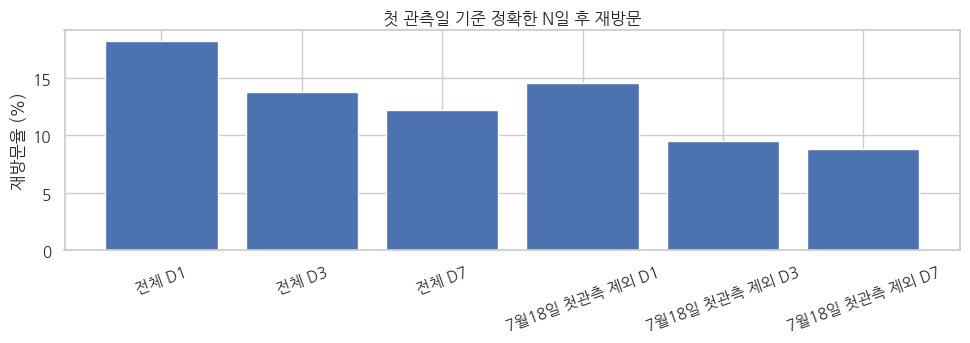

In [ ]:
# Hackle D1·D3·D7 재관측
cf_h = cf_read('mart_hackle_user_daily_24d_v2')
cf_h['date'] = pd.to_datetime(cf_h.activity_date)
cf_HSTART = pd.Timestamp('2023-07-18')
cf_HEND = pd.Timestamp('2023-08-10')
cf_haudit = {'raw_daily_rows': len(cf_h), 'excluded_unknown_or_staff_rows': int((~cf_h.user_id.isin(cf_users.index)).sum())}
cf_h = cf_h[cf_h.user_id.isin(cf_users.index) & cf_h.date.between(cf_HSTART, cf_HEND)].copy()
cf_haudit['pre_signup_rows'] = int((cf_h.date < cf_h.user_id.map(cf_users.signup_date)).sum())
cf_h = cf_h[cf_h.date.ge(cf_h.user_id.map(cf_users.signup_date)) & cf_h.hackle_event_count.gt(0)]
assert not cf_h.duplicated(['user_id', 'date']).any()
cf_hackle_fields = pd.DataFrame([{'field': cf_col, 'total_events': cf_h[cf_col].sum(), 'positive_user_days': cf_h[cf_col].gt(0).sum()} for cf_col in ['hackle_question_start_count', 'hackle_question_complete_count', 'hackle_ping_open_count', 'hackle_shop_event_count']])
display(cf_save(cf_hackle_fields, '13_hackle_field_availability'))
if cf_h.hackle_ping_open_count.sum() == 0:
    cf_show('Ping 열람 집계가 모두 0이다. 계측·매핑 문제를 먼저 점검해야 하므로 실제 미열람으로 처리하지 않고 경험별 재방문 비교를 비워 뒀다.')
cf_first = cf_h.groupby('user_id').date.min()
cf_h['day'] = (cf_h.date - cf_h.user_id.map(cf_first)).dt.days
cf_hb = cf_users.loc[cf_first.index].copy()
cf_hb['first'] = cf_first
cf_hb['first_boundary'] = cf_hb['first'].eq(cf_HSTART)
cf_hb['signup_age_at_first'] = (cf_hb['first'] - cf_hb.signup_date).dt.days
cf_rows = []
for cf_label, cf_mask in [('전체', pd.Series(True, index=cf_hb.index)), ('7월18일 첫관측 제외', ~cf_hb.first_boundary)]:
    for cf_day in [1, 3, 7]:
        cf_b = cf_hb[cf_mask & (cf_hb['first'] + pd.Timedelta(days=cf_day) <= cf_HEND)]
        cf_yes = cf_h.loc[cf_h.day.eq(cf_day), 'user_id'].unique()
        cf_row = cf_rate_row(cf_label + f' D{cf_day}', pd.Series(cf_b.index.isin(cf_yes)))
        cf_rows.append(cf_row)
cf_hr = cf_save(pd.DataFrame(cf_rows), '13_hackle_exact_day_return')
display(cf_hr)
display(pd.Series(cf_haudit))
cf_hb = cf_hb[cf_hb['first'] + pd.Timedelta(days=7) <= cf_HEND].copy()
cf_hb['return_1_7'] = cf_hb.index.isin(cf_h.loc[cf_h.day.between(1, 7), 'user_id'])
cf_hb['return_d7'] = cf_hb.index.isin(cf_h.loc[cf_h.day.eq(7), 'user_id'])
cf_hb['days_0_7'] = cf_h[cf_h.day.between(0, 7)].groupby('user_id').size().reindex(cf_hb.index, fill_value=0)
cf_hb['age_group'] = pd.cut(cf_hb.signup_age_at_first, [-1, 0, 7, 30, np.inf], labels=['가입 당일', '가입 1~7일', '가입 8~30일', '가입 31일+'])
display(cf_save(cf_hb.groupby('age_group', observed=True).agg(users=('first', 'size'), return_1_7=('return_1_7', 'mean'), return_d7=('return_d7', 'mean'), mean_active_days=('days_0_7', 'mean')).reset_index(), '14_hackle_signup_age'))
cf_fig, cf_ax = plt.subplots(figsize=(10, 3.6))
cf_ax.bar(cf_hr.group, 100 * cf_hr.rate)
cf_ax.set(ylabel='재방문율 (%)', title='첫 관측일 기준 정확한 N일 후 재방문')
cf_ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
plt.close('all')
_t7tc_collected = gc.collect()


- Hackle 첫 관측일 이후 D1 방문은 18.21%, D3 13.79%, D7 12.16%다. 7월 18일 첫 관측 사용자를 제외하면 D7은 8.80%다.
- `hackle_ping_open_count` 합계는 0건이지만, 실제 미열람으로 단정할 수 없다.


,group,n,active,rate,ci_low,ci_high,feature,outcome
0,Hackle 첫 관측일 question_complete / False,101408,44165,0.4355,0.4325,0.4386,question_complete,return_1_7
1,Hackle 첫 관측일 question_complete / True,16000,9837,0.6148,0.6072,0.6223,question_complete,return_1_7
2,Hackle 첫 관측일 ping_open / False,117408,54002,0.4600,0.4571,0.4628,ping_open,return_1_7
3,Hackle 첫 관측일 question_start / False,92851,40653,0.4378,0.4346,0.4410,question_start,return_1_7
4,Hackle 첫 관측일 question_start / True,24557,13349,0.5436,0.5374,0.5498,question_start,return_1_7


,feature,label,outcome,common_n,total_n,retained,unexposed_rate,exposed_rate,difference_pp,strata,status
0,question_complete,Hackle 첫 관측일 question_complete,return_1_7,93111,117408,0.7931,0.4131,0.5373,12.4223,53,공통지지 비교
1,ping_open,Hackle 첫 관측일 ping_open,return_1_7,0,117408,0.0000,NaN,NaN,NaN,0,비교군 한쪽 부재
2,question_start,Hackle 첫 관측일 question_start,return_1_7,101198,117408,0.8619,0.4246,0.4697,4.5127,56,공통지지 비교


방문 마트의 Ping 열람 합계도 0건이다. 원천 이벤트 점검이 먼저 필요하다.

,0
all_visits,896009
unmatched_or_staff_visits,269022
conflict_visits,228101


,days_0_7,visits_0_7
count,"117,408.0000","117,408.0000"
mean,2.0283,3.0305
std,1.6024,5.4692
min,1.0000,1.0000
25%,1.0000,1.0000
50%,1.0000,2.0000
75%,2.0000,3.0000
max,8.0000,126.0000


,stat,gap_hours
0,count,"238,376.0000"
1,mean,24.7238
2,std,35.2567
3,min,0.0006
4,25%,2.2242
5,50%,10.1536
6,75%,28.6468
7,90%,73.0540
8,max,191.4428


,behavior,day_order,paired_users,observed_rate,mean_count
0,hackle_question_start_count,1,54002,0.2472,0.3904
1,hackle_question_start_count,2,54002,0.2418,0.3893
2,hackle_question_complete_count,1,54002,0.1822,0.2767
3,hackle_question_complete_count,2,54002,0.1824,0.2851
4,hackle_ping_open_count,1,54002,0.0000,0.0000
5,hackle_ping_open_count,2,54002,0.0000,0.0000
6,hackle_shop_event_count,1,54002,0.0415,0.0948
7,hackle_shop_event_count,2,54002,0.0333,0.0704


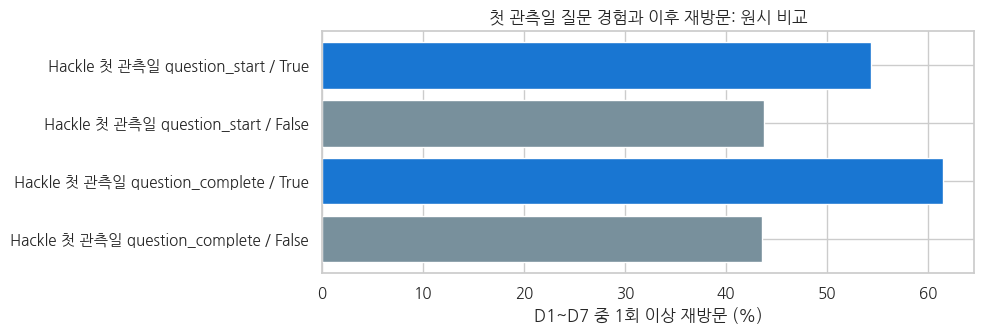

방문 간격에는 7일 안에 다시 방문한 기록만 들어간다. 돌아오지 않은 사람의 대기시간은 빠져 있다. 첫 두 활동일의 차이에는 이용 시간 차이도 섞일 수 있다.

In [ ]:
# 첫 경험·방문 간격·활동일 비교
cf_firstday = cf_h[cf_h.day.eq(0)].set_index('user_id')
cf_hb['question_complete'] = cf_firstday.hackle_question_complete_count.reindex(cf_hb.index).gt(0)
cf_hb['ping_open'] = cf_firstday.hackle_ping_open_count.reindex(cf_hb.index).gt(0)
cf_hb['question_start'] = cf_firstday.hackle_question_start_count.reindex(cf_hb.index).gt(0)
cf_hb['first_date'] = cf_hb['first'].astype(str)
cf_hb['event_band'] = pd.cut(cf_firstday.hackle_event_count.reindex(cf_hb.index), [0, 3, 10, 30, np.inf], labels=['1~3', '4~10', '11~30', '31+']).astype(str)
cf_comparisons = []
cf_adjusted = []
for cf_feature in ['question_complete', 'ping_open', 'question_start']:
    cf_compare(cf_hb, cf_feature, 'Hackle 첫 관측일 ' + cf_feature, 'return_1_7', ['first_date', 'age_group', 'event_band'])
cf_hcompare = cf_save(pd.DataFrame(cf_comparisons), '15_hackle_first_experience_raw')
cf_hadjust = cf_save(pd.DataFrame(cf_adjusted), '16_hackle_first_experience_standardized')
display(cf_hcompare)
display(cf_hadjust)
cf_vis = cf_read('mart_hackle_visit_30m_v2', ['analytics_visit_session_id', 'service_user_id', 'visit_start_at_30m', 'visit_end_at_30m', 'user_conflict_flag', 'ping_open_count'])
cf_show(f'방문 마트의 Ping 열람 합계도 {cf_vis.ping_open_count.sum():,.0f}건이다. 원천 이벤트 점검이 먼저 필요하다.')
assert cf_vis.analytics_visit_session_id.is_unique
cf_vis['start'] = pd.to_datetime(cf_vis.visit_start_at_30m, format='mixed', errors='coerce')
cf_vis['end'] = pd.to_datetime(cf_vis.visit_end_at_30m, format='mixed', errors='coerce')
cf_visit_audit = {'all_visits': len(cf_vis), 'unmatched_or_staff_visits': int((~cf_vis.service_user_id.isin(cf_users.index)).sum()), 'conflict_visits': int(cf_vis.user_conflict_flag.eq(1).sum())}
cf_vis = cf_vis[cf_vis.service_user_id.isin(cf_hb.index) & ~cf_vis.user_conflict_flag.eq(1)].copy()
cf_vis['day'] = (cf_vis.start.dt.normalize() - cf_vis.service_user_id.map(cf_hb['first'])).dt.days
cf_vis = cf_vis[cf_vis.day.between(0, 7)].sort_values(['service_user_id', 'start'])
cf_vis['previous_end'] = cf_vis.groupby('service_user_id')['end'].shift()
cf_vis['gap_hours'] = (cf_vis.start - cf_vis.previous_end).dt.total_seconds() / 3600
cf_hb['visits_0_7'] = cf_vis.groupby('service_user_id').analytics_visit_session_id.nunique().reindex(cf_hb.index, fill_value=0)
display(pd.Series(cf_visit_audit))
display(cf_hb[['days_0_7', 'visits_0_7']].describe())
display(cf_save(cf_vis.loc[cf_vis.gap_hours.ge(0), 'gap_hours'].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).rename_axis('stat').reset_index(), '17_hackle_visit_gaps'))
cf_save(cf_hb[['days_0_7', 'visits_0_7']].value_counts().rename('users').reset_index(), '17_hackle_visit_distribution')
cf_paired = cf_h[cf_h.user_id.isin(cf_hb.index) & cf_h.day.between(0, 7)].sort_values(['user_id', 'date']).copy()
cf_paired['order'] = cf_paired.groupby('user_id').cumcount()
cf_returners = cf_paired.loc[cf_paired.order.eq(1), 'user_id']
cf_paired = cf_paired[cf_paired.user_id.isin(cf_returners) & cf_paired.order.le(1)]
cf_pc = []
for cf_col in ['hackle_question_start_count', 'hackle_question_complete_count', 'hackle_ping_open_count', 'hackle_shop_event_count']:
    for cf_order, cf_g in cf_paired.groupby('order'):
        cf_pc.append({'behavior': cf_col, 'day_order': int(cf_order) + 1, 'paired_users': len(cf_g), 'observed_rate': cf_g[cf_col].gt(0).mean(), 'mean_count': cf_g[cf_col].mean()})
display(cf_save(pd.DataFrame(cf_pc), '18_hackle_paired_return_behavior'))
cf_fig, cf_ax = plt.subplots(figsize=(10, 3.5))
cf_plot = cf_hcompare[cf_hcompare.feature.isin(['question_complete', 'question_start'])].copy()
cf_ax.barh(cf_plot.group, cf_plot.rate * 100, color=['#78909c', '#1976d2', '#78909c', '#1976d2'])
cf_ax.set(xlabel='D1~D7 중 1회 이상 재방문 (%)', title='첫 관측일 질문 경험과 이후 재방문: 원시 비교')
plt.tight_layout()
plt.show()
cf_show('방문 간격에는 7일 안에 다시 방문한 기록만 들어간다. 돌아오지 않은 사람의 대기시간은 빠져 있다. 첫 두 활동일의 차이에는 이용 시간 차이도 섞일 수 있다.')
plt.close('all')
_t7tc_collected = gc.collect()


- 첫 관측일 이후 7일 구간에서 관측된 방문 간격의 중앙값은 10.15시간, 평균은 24.72시간이다.
- 첫 두 활동일이 관측된 54,002명에서 질문 완료 관측률은 약 18.2%로 비슷했고, 상점 이벤트는 4.15%에서 3.33%로 낮아졌다.


### 3-7-8. 후속 검증 방향

- 학교 활동량·개인 DB 행동·Hackle 방문의 정의를 구분하고, 반응 수신과 후속 행동의 시간적 연결을 추가로 확인해야 한다.


In [ ]:
# 후기 활동 근거·개선 방향
cf_r = cf_db_summary[(cf_db_summary.group == 'D8~D30') & (cf_db_summary.kind == 'core')].iloc[0]
cf_rx = cf_db_summary[(cf_db_summary.group == 'D8~D30') & (cf_db_summary.kind == 'extended')].iloc[0]
cf_repeat_share = cf_repeat.loc[cf_repeat.pattern.eq('여러 주 반복'), 'share'].sum()
cf_ret7 = cf_hr[cf_hr.group.eq('전체 D7')].iloc[0]
cf_fr = cf_fullmay.iloc[0]
cf_lines = [f'- 5월 전체 가입자의 D8~D30 친구 요청 발송률은 {cf_fr.rate:.2%}({cf_fr.active:,.0f}/{cf_fr.n:,.0f})다. 하위 코호트의 핵심 DB 활동률은 {cf_r.rate:.2%}({cf_r.active:,.0f}/{cf_r.n:,.0f})다. 하위 코호트에서 출석을 포함하면 {cf_rx.rate:.2%}다. 행동 정의가 달라 앱 방문율 하나로 합칠 수는 없다.', f'- D8~D30에 여러 주 반복한 비율은 {cf_repeat_share:.2%}다. 후기 기록이 한 번 남은 경우보다 반복 사용의 범위가 좁다.', f'- Hackle 첫 관측일 기준 D7 방문은 {cf_ret7.rate:.2%}({cf_ret7.active:,.0f}/{cf_ret7.n:,.0f})다. 5월 가입자와는 별도의 표본이다.']
for cf__, cf_row in cf_hadjust[cf_hadjust.difference_pp.notna()].iterrows():
    cf_lines.append(f'- {cf_row.feature}: 층화 후 D1~D7 방문율 차이는 {cf_row.difference_pp:+.2f}%p다. 비교에 남은 표본은 {cf_row.retained:.1%}다. 경험의 효과를 확정한 결과는 아니다.')
cf_lines.append('- Ping 열람은 계측상 0건이라 비교가 어렵다. 질문 분석은 10개교 안에서도 초기 경험이 없는 쪽이 작아, 층화 후 남는 표본이 적다.')
cf_show('\n\n'.join(cf_lines))
cf_db_text = []
for cf__, cf_row in cf_adjustment.iterrows():
    if pd.notna(cf_row.difference_pp):
        cf_db_text.append(f'- {cf_row.label}: 공통층 차이 {cf_row.difference_pp:+.2f}%p, 표본 유지율 {cf_row.retained:.1%}. {cf_row.status}.')
    else:
        cf_db_text.append(f'- {cf_row.label}: {cf_row.status}. 차이를 계산할 비교 표본이 부족하다.')
cf_show('**DB 초기 경험 비교**\n\n' + '\n'.join(cf_db_text) + '\n\n친구 요청 발송과 초기 핵심 활동일은 많이 겹친다. 비교에 남은 표본이 좁아 차이의 방향이 바뀌어도 발송의 부정적 효과로 보기는 어렵다. 피드백 작성자의 차이는 층화 후 거의 사라졌다.')
cf_decision = pd.DataFrame([['반응 수신 → 확인', 'DB 수신 시각은 활용 가능하지만 과거 열람 시각은 불명', '수신·알림 전달·열람 시각을 연결해 확인 진입을 검증'], ['질문 완료 → 후속 활동', '10개교 DB 생성 기록과 Hackle 첫날 완료 연관성을 별도 확인', '결과 확인 이후 다음 콘텐츠·답변 경로를 실험'], ['첫 복귀 → 반복 사용', '여러 주 활동과 첫 공백 후 복귀를 구분', '후속 가치 공급 시점과 반복 상호작용을 검증'], ['부정 경험 → 이후 활동', '신고 작성 자체는 활동량과 연관; 현재 상태는 과거 노출이 아님', '정확한 노출·사건·대응 시각을 계측하고 안전 조치와 지속 사용을 함께 평가']], columns=['제품 질문', '현재 근거의 범위', '다음 검증'])
display(cf_save(cf_decision, '19_product_decisions'))
cf_limitations = '현재 계정·학교로 연결한 표본이며 질문은 10개교 자료다. 기록이 없는 날을 앱 이탈로 셀 수 없고, 수집의 완전성과 시간대도 확정하지 못했다.\n\n최종 수락·열람 상태에는 실제 발생 날짜가 없다. 층화 후에도 다른 요인과 학교 안의 유사성이 남는다. Hackle 첫 관측 역시 서비스 첫 방문과 다를 수 있다.'
cf_show('**한계:** ' + cf_limitations)
assert cf_db_summary.active.le(cf_db_summary.n).all()
assert cf_hr.active.le(cf_hr.n).all()
assert cf_hb['first'].add(pd.Timedelta(days=7)).le(cf_HEND).all()
assert cf_a.age.ge(0).all()
print('검증 완료: 사용자-날짜 유일성, 가입 전 기록 제외, 분모 범위, Hackle 후속 관측기간.')
print('집계 결과는 각 셀의 표·차트에 표시됩니다.')
plt.close('all')
_t7tc_collected = gc.collect()


- 5월 전체 가입자의 D8~D30 친구 요청 발송률은 27.44%(174,365/635,505)다. 하위 코호트의 핵심 DB 활동률은 24.37%(81,917/336,194)다. 하위 코호트에서 출석을 포함하면 53.59%다. 행동 정의가 달라 앱 방문율 하나로 합칠 수는 없다.

- D8~D30에 여러 주 반복한 비율은 4.96%다. 후기 기록이 한 번 남은 경우보다 반복 사용의 범위가 좁다.

- Hackle 첫 관측일 기준 D7 방문은 12.16%(14,274/117,408)다. 5월 가입자와는 별도의 표본이다.

- question_complete: 층화 후 D1~D7 방문율 차이는 +12.42%p다. 비교에 남은 표본은 79.3%다. 경험의 효과를 확정한 결과는 아니다.

- question_start: 층화 후 D1~D7 방문율 차이는 +4.51%p다. 비교에 남은 표본은 86.2%다. 경험의 효과를 확정한 결과는 아니다.

- Ping 열람은 계측상 0건이라 비교가 어렵다. 질문 분석은 10개교 안에서도 초기 경험이 없는 쪽이 작아, 층화 후 남는 표본이 적다.

**DB 초기 경험 비교**

- 초기 친구요청 발송: 공통층 차이 -6.86%p, 표본 유지율 33.4%. 제한적 공통지지.
- 초기 친구요청 수신: 공통층 차이 +2.40%p, 표본 유지율 95.5%. 공통지지 비교.
- 초기 결제 성공: 공통층 차이 -2.03%p, 표본 유지율 94.8%. 공통지지 비교.
- 초기 피드백·신고 작성: 공통층 차이 -0.05%p, 표본 유지율 97.5%. 공통지지 비교.
- 10개교 초기 질문 생성: 양군 20명 이상 공통층 없음. 차이를 계산할 비교 표본이 부족하다.
- 10개교 초기 투표 기록: 공통층 차이 +14.39%p, 표본 유지율 5.1%. 제한적 공통지지.
- 10개교 초기 Ping 수신: 공통층 차이 -49.78%p, 표본 유지율 1.2%. 제한적 공통지지.

친구 요청 발송과 초기 핵심 활동일은 많이 겹친다. 비교에 남은 표본이 좁아 차이의 방향이 바뀌어도 발송의 부정적 효과로 보기는 어렵다. 피드백 작성자의 차이는 층화 후 거의 사라졌다.

,제품 질문,현재 근거의 범위,다음 검증
0,반응 수신 → 확인,DB 수신 시각은 활용 가능하지만 과거 열람 시각은 불명,수신·알림 전달·열람 시각을 연결해 확인 진입을 검증
1,질문 완료 → 후속 활동,10개교 DB 생성 기록과 Hackle 첫날 완료 연관성을 별도 확인,결과 확인 이후 다음 콘텐츠·답변 경로를 실험
2,첫 복귀 → 반복 사용,여러 주 활동과 첫 공백 후 복귀를 구분,후속 가치 공급 시점과 반복 상호작용을 검증
3,부정 경험 → 이후 활동,신고 작성 자체는 활동량과 연관; 현재 상태는 과거 노출이 아님,정확한 노출·사건·대응 시각을 계측하고 안전 조치와 지속 사용을 함께 평가


**한계:** 현재 계정·학교로 연결한 표본이며 질문은 10개교 자료다. 기록이 없는 날을 앱 이탈로 셀 수 없고, 수집의 완전성과 시간대도 확정하지 못했다.

최종 수락·열람 상태에는 실제 발생 날짜가 없다. 층화 후에도 다른 요인과 학교 안의 유사성이 남는다. Hackle 첫 관측 역시 서비스 첫 방문과 다를 수 있다.

검증 완료: 사용자-날짜 유일성, 가입 전 기록 제외, 분모 범위, Hackle 후속 관측기간.
집계 결과는 각 셀의 표·차트에 표시됩니다.


**다음에 검증할 점**

- 반응 수신·알림 전달·실제 열람 시각을 연결해 확인 경로를 검증한다.
- 질문 완료 후 결과 확인·다음 질문·답변 경로가 반복 활동으로 이어지는지 실험한다.
- 부정 경험의 발생·대응 시각을 함께 기록해 안전 조치와 후기 활동의 관계를 평가한다.


In [ ]:
# Continuation 결과·임시 변수 정리
continuation_followup_results = {name: globals().get('cf_' + name) for name in ['db_summary', 'hr', 'decision', 'adjustment', 'hadjust']}
t7tc_release('cf_')


파트 임시 데이터 메모리 정리 완료: cf_


# **4. 인사이트**

- 일곱 가지 분석 결과를 종합해 가입 이후 이용이 이어지지 않는 지점을 정리했다.
- 주요 문제를 첫 참여·질문 경험·반응과 대화·재방문의 네 구간으로 연결했다.

## 4-1. 프로젝트 목적과 종합 진단

본 프로젝트는 학교 네트워크 기반 소셜 앱 **Ping의 유입 이후 이용 경험을 진단하고, 첫 참여부터 반응과 재방문까지 제품 경험을 재구축**하는 것을 목표로 한다. 초기 가입과 친구요청이 집중된 이후에도 질문 참여와 상호작용이 이어졌는지를 살펴봤다.

흩어진 로그와 지표 기준을 정리한 뒤, **Growth·Network·Content·Interaction·Value·Trust·Continuation**의 일곱 관점으로 이용 구간을 나누어 분석했다. 친구요청은 이미 가입한 사용자 사이의 연결이므로, 이 결과를 외부 초대에 의한 신규 유입이나 바이럴의 인과효과로 해석하지 않는다.

| 분석 관점 | 핵심 관측과 해석 | 재구축에 반영할 방향 |
| --- | --- | --- |
| **Growth — 학교 활성화** | 관측된 5,551개 학교 중 1,654개가 40명에 도달하지 못했다. 4~5월 도달 학교의 평균 추가 가입자는 도달 후 첫째 주 89.28명에서 둘째 주 13.17명으로 줄었다. 학교 개방 여부와 개방 이후의 참여를 나누어 볼 필요가 있다. | 학교 인원에 따른 단계적 개방과 첫 질문 진입 경로 |
| **Network — 친구 관계 형성** | 최종 수락 관계망에서 학교별 최대 연결요소 포함 비율의 중앙값은 96.59%였다. 다만 첫 주에 요청을 보낸 사용자 중 둘째 주에도 요청한 비율은 집단별로 낮았고, 40명 도달 이후 가입자는 18.7%였다. 연결망이 존재하는 것과 관계 행동이 이어지는 것은 별개의 문제다. | 친구요청 수락 뒤 질문 참여 연결, 보낸 Ping 상태와 실제 반응 확인 |
| **Content — 질문의 새로움과 공급** | 분석한 10개 학교에서 상위 10% 문구가 질문조각의 53.0%를 차지했다. 10개 학교 공통 문구의 질문조각 비중은 96.08%였고, 한 학교에만 등장한 문구는 1개였다. 누적 질문조각 501개 이상 구간의 의미 반복률은 34.42%였다. 공급의 다양성, 학교별 차별화, 개인별 반복을 함께 관리할 필요가 있다. | 학교 로컬 질문, 사용자 질문 제안, 의미 중복과 개인별 재노출 관리 |
| **Interaction — 질문 완료 이후 행동** | 질문 시작 방문의 순차 완료 비율은 73.75%였지만, 순차 완료 방문에서 다음 질문으로 이어진 비율은 2.12%였다. 전체 완료 방문의 26.2%에서는 완료 뒤 다음 분류 가능 행동이 관측되지 않았다. 완료 이후의 경로를 별도로 살펴볼 필요가 있다. | 완료 화면에서 실제 받은 결과·반응을 확인하는 경로 |
| **Value — 주고받은 반응과 가치** | C0·C2와 C1·C3는 발송·확인·답장·결제 행동에서 차이를 보였다. 수신 대비 답장 수준도 집단별로 달랐다. 최종 답장 상태와 다음 날 투표 참여의 연관은 확인했지만, 실제 답장 시각이나 그 효과를 확정한 것은 아니다. | 무료 반응, 보낸 Ping 상태, 선택적 역질문·채팅, 결과·배지 |
| **Trust — 불편한 경험과 안전** | 신고의 개인화 사유와 안전 사유를 구분할 필요가 있었다. 외모·신체 비하의 질문당 평균 신고는 89.87건이었지만, 질문 수와 배정량이 달라 단순 건수만으로 위험도를 비교하기 어렵다. 모델의 게시 등급에도 과거 안전 사유 신고 이력이 있는 질문이 남았다. | 신고 유형별 대응, 규칙·모델 기반 검토 보조, 게시 이후 재검토 |
| **Continuation — 후기 이용과 재방문** | 친구요청·결제 등 핵심 DB 행동, 출석을 포함한 활동, Hackle 방문은 서로 다른 지표다. 한 번 다시 관측된 기록과 여러 주 반복한 활동도 구분해야 한다. 후속 관측 여부만으로 관계·질문 경험의 지속을 설명하기 어렵다. | 방문 목적에 맞는 홈, 실제 새 소식 안내, 출석 이후 선택적 참여 |

## 4-2. 일곱 진단을 네 가지 이용 구간으로 연결

| 재구축 구간 | 연결한 분석 | 해결하려는 이용 경험 |
| --- | --- | --- |
| **첫 참여** | Growth, Network | 학교 개방을 기다리는 동안 참여 기회가 제한되고, 친구 연결 이후 첫 질문으로 이어지는 경로가 필요함 |
| **질문 경험** | Content, Trust | 공통 문구 중심의 공급, 의미 반복, 맞지 않는 질문·후보, 안전 검토를 함께 다룰 필요가 있음 |
| **반응과 대화** | Interaction, Value | 질문을 완료하거나 지목을 받은 경험이 실제 반응을 주고받는 행동으로 이어지는지 확인할 필요가 있음 |
| **재방문** | Continuation, Value | 다시 들어온 이용자가 미확인 결과나 새 질문처럼 방문 목적에 맞는 다음 행동을 찾도록 돕는 경험이 필요함 |

이 연결은 관측 결과를 바탕으로 세운 개선 가설이다. 특정 기능이 이탈을 막거나 재방문을 높인다는 효과를 입증한 결과는 아니다.


# **5. 서비스 재구축**

- 분석에서 확인한 문제를 바탕으로 개선 화면과 이용 흐름을 설계했다.
- 사용자 유형별 행동 차이를 반영하고, 기능별 운영 기준과 선택 경로를 구체화했다.


## 5-1. 재구축 방향

**첫 참여, 질문 경험, 반응과 대화, 재방문**의 네 구간으로 구성했다. 분석에서 발견한 문제를 화면과 운영 조건에 연결하되, 아래 기능은 실제 서비스에 적용해 성과를 확인한 기능이 아니라 **설계한 개선 방향과 체험용 프로토타입**이다.

### ① 첫 참여 — 학교 인원에 맞춘 참여 범위

40명 미도달 학교가 다수 관측됐다는 점을 바탕으로, 전체 개방 전에도 제한된 질문 참여를 경험하도록 단계적 개방을 설계했다. 학교 개방이나 친구요청 수락 이후에는 첫 질문으로 진입하는 경로를 연결했다.

| 학교 인원 | 프로토타입의 이용 범위 | 설계 목적 |
| --- | --- | --- |
| **0~14명** | 서비스 소개, 친구 초대 링크·QR | 서비스의 이용 방식과 학교 개방 조건 안내 |
| **15~24명** | 실제 질문 2개, 학교·전체 범위의 질문 제안, 친구 초대 | 전체 개방을 기다리는 동안 첫 지목 경험 제공 |
| **25~39명** | 학교 로컬 질문, 받은 Ping·결과 읽기, 질문 제안 | 학교 맥락의 질문과 받은 결과 확인으로 경험 확장 |
| **40명 이상** | 일반 10문항과 반응·채팅을 포함한 전체 기능 | 질문에서 상호작용까지 전체 흐름 연결 |

**15명·25명은 분석으로 도출한 최적 임계값이 아니라 검증이 필요한 운영 설정이다.** 25~39명 단계의 받은 Ping은 읽기 중심이며, 반응·채팅은 전체 개방 이후의 기능으로 구분했다.

### ② 질문 경험 — 새로움, 적합성, 안전 관리

| 개선 화면·운영 | 분석 근거 또는 추가로 필요한 정보 | 설계 내용 |
| --- | --- | --- |
| **학교 로컬 질문** | 10개 학교 공통 문구가 질문조각의 96.08%를 차지했고, 한 학교에만 등장한 문구는 1개였다. | 학교 축제·행사처럼 함께 겪는 일을 소재로 일반 10문항에 로컬 질문을 편성한다. 학교별 차별화가 부족했다는 관측을 바탕으로 한 설계이며, 기존 공통 질문에 학교생활 소재가 전혀 없었다는 뜻은 아니다. |
| **건너뛰기 이유** | 넘긴 기록만으로는 질문이 반복됐는지, 불편했는지, 어울리는 친구가 없었는지 알 수 없다. 신고의 개인화 사유와 스킵 원인도 동일한 것으로 취급할 수 없다. | 이유를 선택적으로 수집해 후보 구성과 질문 추천·검토에 구분해 반영한다. 이유를 입력하지 않고 넘기는 경로도 유지한다. |
| **학교·전체 질문 제안** | 신규 문구는 7월에 1개만 등장했고 이후 관측되지 않았다. 학교별 고유 문구도 적었다. | 이용자가 학교 또는 전체 범위로 질문 소재를 제안하는 경로를 둔다. 공급 감소의 원인을 확정한 것은 아니며, 제안이 실제로 다양성과 적합성을 높이는지는 검증한다. |
| **게시 전 규칙·모델 검토** | 과거 안전 사유 신고 이력을 예측한 모델에도 누락이 있었다. 주제 분류 자체가 유해성 판정은 아니다. | 음주·폭력 확정 키워드는 우선 제한하고, 규칙·모델로 게시·검토·제한 등급을 나눈다. 제한·검토 등급은 담당자가 확인한다. |
| **게시 후 중복·재노출 관리** | 상위 10% 문구에 질문조각의 53.0%가 집중됐고, 누적 501개 이상 구간의 의미 반복률은 34.42%였다. | 유사 의미 질문의 공급 집중과 개인별 재노출 간격을 조정한다. 질문조각 대비 신고율을 살피고, 신고가 들어온 질문과 유사 질문군을 재검토한다. |
| **질문 완료 화면** | 같은 방문의 완료 후 다음 질문 전환은 2.12%였으며, 완료 후 다음 분류 가능 행동이 관측되지 않은 경우도 있었다. | 완료 보상과 후속 행동을 분리하고, 실제 도착한 결과·반응이 있으면 바로 확인하는 대표 경로를 둔다. 다음 질문 전환이 낮다는 사실만으로 다른 모든 행동도 낮다고 일반화하지 않는다. |

### ③ 반응과 대화 — 받은 마음에 답하는 부담 완화

| 개선 화면 | 분석과의 연결 | 설계 내용 |
| --- | --- | --- |
| **무료 반응·짧은 답장** | 수신 대비 답장이 적었던 C1의 행동과, 최종 답장 상태별 다음 날 투표 차이를 참고했다. 답장 비율이 낮은 원인이 비용이나 입력 부담인지는 확인하지 못했다. | 기본 이모지·스티커·선택형 문구와 50자 이내 직접 답장을 무료로 보내는 흐름을 구성했다. 자동 반응을 만들지 않고 사용자가 실제 보낸 반응만 알린다. |
| **보낸 Ping 상태** | 발송·확인 행동이 활발했던 C0를 참고했다. | 전송 완료, 열람, 실제 반응 도착을 목록과 상세 화면에서 구분한다. |
| **선택적 역질문** | 반응과 후속 참여의 관측 연관을 바탕으로, 상호작용을 이어가는 선택지를 검토했다. | 상대의 이름·초성을 알아내지 않아도 원래 Ping을 보낸 친구에게 다른 질문을 보낼 수 있도록 설계했다. |
| **선택 채팅과 하트 반환** | 유료 이용이 관측된 C2를 고려해 비용 지출 이후의 경험까지 설계 범위에 포함했다. | 채팅 개설 전에 200하트 사용과 반환 조건을 안내한다. 첫 요청 후 72시간 동안 실제 답장이 없으면 사용 하트를 반환하는 구조다. |

**무료화·역질문·200하트·72시간 반환은 검증할 설계 가설이다.** 기존 분석이 각 기능의 효과나 금액·시간의 최적값을 입증한 것은 아니다.

### ④ 재방문 — 방문 목적에 맞는 다음 행동

| 개선 화면 | 설계 배경 | 설계 내용 |
| --- | --- | --- |
| **상태에 맞는 홈** | 방문 기록, 출석 기록, 질문·관계 행동을 구분해 다음 행동을 연결할 필요가 있다. | 새 Ping이 있으면 결과를 먼저 보여주고, 없으면 새 질문이나 처음 만나는 테마를 안내한다. 알림은 실제 새 정보가 생긴 경우로 제한한다. |
| **내 결과·대표 배지** | 발송 대비 수신 비율은 높지만 반응은 적었던 C3를 참고했다. | 받은 결과를 모아보고 획득한 배지 중 하나를 대표 배지로 고르는 흐름을 구성했다. 공개 범위는 이용자가 선택한다. 배지 선호나 재방문 효과를 확인한 결과는 아니다. |
| **출석 이후 선택 행동** | 출석을 포함한 활동과 핵심 행동을 구분하고, 다시 들어온 이후의 참여를 별도로 확인하려 한다. | 출석 보상은 바로 지급하고 받은 Ping이나 오늘의 미션을 다음 선택지로 둔다. 미션 보상은 출석 보상과 분리한다. |

### 클러스터를 별도 서비스가 아닌 공통 이용 흐름에 반영

| 군집 | 참고한 행동 특성 | 연결한 개선 화면 |
| --- | --- | --- |
| **C0 — 적극 발송·확인형** | 발송과 확인·반응 행동이 상대적으로 활발함 | 보낸 Ping 상태, 실제 반응 확인, 선택적 역질문 |
| **C1 — 수신 우위 일반형** | 받은 지목에 비해 답장 수준이 낮음 | 무료 이모지·스티커·짧은 답장 |
| **C2 — 유료 이용형** | 유료 이용과 힌트 탐색이 관측됨 | 역질문, 선택 채팅, 비용·하트 반환 조건 |
| **C3 — 수신 우위·저반응형** | 발송 대비 수신 비율이 높지만 반응은 적음 | 내 결과 모아보기, 대표 배지, 선택 공개 |

군집별 기능을 강제로 배정하거나 다른 집단의 이용을 제한하는 구조는 아니다. **하나의 서비스 안에서 선택할 수 있는 기능을 설계할 때 군집별 차이를 참고했다.**

## 5-2. 핵심 유저 플로우

1. **가입·학교 연결:** 학교 검색이나 초대 링크·QR로 진입한다.
2. **학교 단계에 맞춘 질문 참여:** 초기에는 2문항, 전체 개방 후에는 일반 10문항을 이용한다. 질문 중단·재개와 건너뛰기를 지원한다.
3. **후보 선택과 지목 전송:** 학교 친구를 고르고, 질문 완료 시 실제 도착한 결과가 있으면 확인하는 경로를 제공한다.
4. **받은 Ping 확인과 실제 반응:** 전체 개방 후 무료 반응·짧은 답장·역질문을 선택한다. 채팅은 별도의 선택 경로다.
5. **새 소식을 통한 다음 방문:** 발송자에게 실제 반응이 도착했음을 알리고, 홈에서 미확인 Ping과 새 질문을 안내한다.

체험용 프로토타입: [Ping UI/UX 재구축 데모](https://lucyjeehyeon.github.io/ping-demo/)

# **6. 결론 및 한계**

- 프로젝트의 핵심 결론과 개선 효과를 확인할 검증 지표를 정리했다.
- 데이터의 관측 범위와 해석의 한계를 밝히고, 추가 검증이 필요한 사항을 구분했다.

## 6-1. 결론

**재구축의 중심은 유입 이후의 관계 경험이다.** 초기 가입과 친구요청이 집중됐다는 사실만으로 질문 참여, 반응, 반복 이용까지 이어졌다고 볼 수는 없었다. 학교 개방, 질문 공급, 완료 이후 행동, 반응의 차이, 안전 검토와 후속 활동을 각각 살펴볼 필요가 있었다.

본 프로젝트는 일곱 관점의 분석을 바탕으로 **첫 참여를 쉽게 하고, 실제 반응을 다음 참여로 연결하는 경험**을 구체화했다.

- **진입:** 학교 인원에 맞춰 참여 범위를 단계적으로 연다.
- **질문:** 학교 로컬 질문과 사용자 제안으로 소재를 넓히고, 중복·개인별 재노출과 부적합한 경험을 관리한다.
- **반응:** 무료 반응과 선택적 역질문·채팅으로 받은 마음에 답할 경로를 만든다.
- **재방문:** 미확인 결과와 실제 새 소식을 방문 목적에 맞는 다음 행동으로 연결한다.

최종 산출물은 **분석 결과, 개선 화면, 유저 플로우와 체험용 프로토타입, 검증 계획**이다. 실서비스에 적용한 뒤 매출·재방문·안전성이 개선됐다는 성과를 확인한 것은 아니다.


## 6-2. 기대효과와 검증 계획

학교 안의 사용자들은 서로 영향을 주므로, 학교 단위 비교 실험 또는 단계적 적용을 검토한다. 비교 학교의 규모·가입 시기·관측 기간을 맞추고, 결과를 보기 전에 주요 지표와 행동 발생 시점의 수집 기준을 정한다.

| 검증할 설계 | 기대하는 변화 | 주요 확인 지표 | 함께 점검할 부작용 |
| --- | --- | --- | --- |
| **학교 단계 개방** | 전체 개방 이전의 첫 참여와 개방 이후 질문 진입 | 15~39명 학교의 첫 질문 참여율, 40명 도달 학교 비율, 도달 후 7일 내 첫 질문 참여율 | 건너뛰기, 후보 부족, 질문 배정·노출 대비 신고 |
| **질문 공급·검토 관리** | 새로운 질문 경험과 반복 감소 | 의미 반복률, 신규 질문 배정·노출 비율, 검토 대상 및 처리량 | 전체·안전 사유 신고율, 검토 누락, 운영자 검토 부담 |
| **무료 반응·역질문** | 실제 반응을 주고받는 경험과 후속 참여 | 실제 반응 시각을 수집한 뒤의 24시간 내 반응 발생 비율, 다음 날 투표 참여율 | 알림 차단·해제, 원치 않는 상호작용·신고, 결제 변화 |
| **상태에 맞는 홈·출석 후 선택 행동** | 다시 들어온 뒤 핵심 행동으로 연결 | 방문 후 질문·반응 등 사전에 정의한 핵심 행동 전환율, 반복 활동 | 알림 차단·해제, 보상만을 위한 형식적 활동 |

‘24시간 내 반응’은 **향후 실제 반응 시각을 기록해 검증할 지표**다. 최종 답장 상태를 사용하는 현재 Value 분석과 구분한다. 실제 노출 이벤트를 추가하기 전에는 질문조각 배정량을 분모로 삼았다는 점도 함께 표시한다.

## 6-3. 분석과 설계의 한계

| 구분 | 해석과 적용 시 유지할 조건 |
| --- | --- |
| **모집단·기간 차이** | 전체 학교, 특정 시기에 40명에 도달한 학교, 10개 학교, Hackle 관측 사용자, 5월 가입 코호트는 서로 다른 표본이다. 모든 숫자를 하나의 퍼널이나 동일한 이용자의 변화로 연결할 수 없다. |
| **행동 관측의 범위** | DB 핵심 행동·출석·Hackle 방문은 정의가 다르다. 관측되지 않은 행동을 곧바로 앱 미방문이나 영구 이탈로 해석하지 않는다. 길이가 다른 가입 후 구간의 관측률도 일반적인 일별 리텐션과 구분한다. |
| **최종 상태와 행동 시점** | 친구요청 생성부터 마지막 갱신까지의 간격은 실제 수락 시각의 대용치다. Ping의 최종 열람·답장 상태 역시 실제 행동 시각이나 선후관계를 보장하지 않는다. |
| **관계망 스냅샷** | 최종 수락 관계망의 구조를 측정한 결과다. 학교 개방 당시에도 같은 관계망이 존재했다고 볼 수 없다. |
| **질문조각과 실제 열람** | 공급 집중도·의미 반복률·배정량 대비 신고율은 질문조각을 기준으로 한다. 실제 열람, 체감 반복, 피로도나 위해를 직접 측정한 것은 아니다. |
| **인과와 일반화** | 관측된 행동 차이는 원인이나 기능 효과를 입증하지 않는다. 10개 학교 결과의 전체 학교 일반화, 비무작위 비교와 반복 사용자 기록에 따른 통계적 한계를 고려해야 한다. |
| **군집의 의미** | 군집은 행동을 요약한 집단이며 고정된 성격이나 욕구를 확정하는 분류가 아니다. 군집 생성에 쓴 피처의 차이는 독립적인 유효성 검증이 아니며, 수신/발신 비율이 높다는 사실도 절대 수신량이 많다는 뜻은 아니다. |
| **Value 가설의 범위** | 최종 답장 상태와 다음 날 투표의 연관을 24시간 내 답장의 효과로 설명하지 않는다. C1·C3의 답장 수준과 학교 활성 일수는 분석한 10개 학교에서 통계적으로 유의한 관계를 확인하지 못했다. |
| **Trust 예측의 범위** | 주제 라벨은 유해성 정답이 아니다. 과거 안전 사유 신고 이력의 예측 성능은 실제 유해성 판정이나 운영 중 사전 차단 성과와 다르다. 문구 중복·데이터 분할·모델 선택에 따른 성능 추정의 한계도 남아 있다. 모델은 검토 우선순위를 돕는 수단으로 사용한다. |
| **코드·데이터와 수치의 정합성** | GitHub 코드의 모집단·분모·시간 정의를 기준으로 한다. PPT와 정의가 다르거나 출처가 확인되지 않은 값은 확정 수치로 옮기지 않는다. 특히 후기 출석만 관측 비율과 Value의 시간 기준은 앞선 분석의 실제 출력·정의를 우선한다. |
| **운영 설정과 효과 미검증** | 15명·25명 단계, 무료 반응, 200하트·72시간 반환, 배지·미션 등은 설계 설정이다. 자동 공개와 운영자 승인 범위도 실제 적용 전에 통일해야 한다. 프로토타입 시연은 사용 흐름을 보여주며 효과 검증을 대신하지 않는다. |

## 6-4. 프로젝트 자료

- [GitHub — 분석 코드 및 프로젝트 문서](https://github.com/codeit-team7/team7)
- [프로토타입 직접 체험](https://lucyjeehyeon.github.io/ping-demo/)
- [구글 드라이브 — 프로젝트 산출물](https://drive.google.com/drive/folders/1-HHxhMjHz3LRGPzDQtLz_nErmhIBsbj0?usp=sharing)
- [노션 — 프로젝트 기록](https://app.notion.com/p/DA-15-4-_7-3b89be1e836280a1bbafd7cee1e55060?source=copy_link)